## I am going to start modelling  eden dataset

In [ ]:
# ==============================================================
# MODELLING STEP 1, PART 1
# Controlled loading and structural validation
# ==============================================================

from IPython import display
from pathlib import Path

import numpy as np
import pandas as pd


# --------------------------------------------------------------
# 1. Define the existing Eden project folders
# --------------------------------------------------------------

PROJECT_ROOT = Path("/Users/ryansmac/Desktop/Meng Project")
EDEN_DATASETS_DIR = PROJECT_ROOT / "eden_datasets"

# Keep the existing folder spelling used during forecast preparation.
FORECAST_PREPARATION_DIR = EDEN_DATASETS_DIR / "forceast_preparation"

# New folder for the modelling phase.
MODELLING_DIR = EDEN_DATASETS_DIR / "modelling"


# --------------------------------------------------------------
# 2. Create the modelling folder structure
# --------------------------------------------------------------

MODELLING_SUBFOLDERS = [
    "01_pipeline_setup",
    "02_baselines",
    "03_model_selection",
    "04_final_test",
    "05_final_forecasts",
    "models",
    "results",
    "plots",
]

for folder_name in MODELLING_SUBFOLDERS:
    folder_path = MODELLING_DIR / folder_name
    folder_path.mkdir(parents=True, exist_ok=True)

SETUP_OUTPUT_DIR = MODELLING_DIR / "01_pipeline_setup"

print("Modelling folder created or confirmed:")
print(MODELLING_DIR)


# --------------------------------------------------------------
# 3. Define the files allowed during model-selection setup
# --------------------------------------------------------------

MODEL_SELECTION_FILES = {
    "MODEL_SELECTION_TRAINING":
        FORECAST_PREPARATION_DIR /
        "17_model_selection_training_dataset.csv",

    "MODEL_SELECTION_VALIDATION":
        FORECAST_PREPARATION_DIR /
        "17_model_selection_validation_dataset.csv",

    "FROZEN_FEATURE_CONTRACT":
        FORECAST_PREPARATION_DIR /
        "17_frozen_model_feature_contract.csv",

    "FORECASTING_PROTOCOL":
        FORECAST_PREPARATION_DIR /
        "17_forecasting_protocol_contract.csv",
}


# --------------------------------------------------------------
# 4. Register the protected final-test files
#
# These paths are recorded only so that their protected status can
# be documented. Their contents are NOT loaded in this notebook part.
# --------------------------------------------------------------

PROTECTED_FINAL_TEST_FILES = {
    "RESERVED_FINAL_TEST_TRAINING":
        FORECAST_PREPARATION_DIR /
        "17_reserved_final_test_training_dataset.csv",

    "RESERVED_FINAL_TEST_SCORING_FEATURES":
        FORECAST_PREPARATION_DIR /
        "17_reserved_final_test_scoring_features.csv",

    "RESERVED_FINAL_TEST_TARGET_VAULT":
        FORECAST_PREPARATION_DIR /
        "17_reserved_final_test_target_vault.csv",
}


# --------------------------------------------------------------
# 5. Confirm that all required files exist
# --------------------------------------------------------------

all_registered_files = {
    **MODEL_SELECTION_FILES,
    **PROTECTED_FINAL_TEST_FILES,
}

missing_files = [
    str(file_path)
    for file_path in all_registered_files.values()
    if not file_path.exists()
]

if missing_files:
    missing_text = "\n".join(missing_files)

    raise FileNotFoundError(
        "The following required files were not found:\n"
        f"{missing_text}\n\n"
        "Check PROJECT_ROOT and FORECAST_PREPARATION_DIR."
    )

print("\nAll required files were found.")


# --------------------------------------------------------------
# 6. Load only the permitted model-selection files
# --------------------------------------------------------------

training_df = pd.read_csv(
    MODEL_SELECTION_FILES["MODEL_SELECTION_TRAINING"],
    low_memory=False,
)

validation_df = pd.read_csv(
    MODEL_SELECTION_FILES["MODEL_SELECTION_VALIDATION"],
    low_memory=False,
)

feature_contract_df = pd.read_csv(
    MODEL_SELECTION_FILES["FROZEN_FEATURE_CONTRACT"],
    low_memory=False,
)

protocol_contract_df = pd.read_csv(
    MODEL_SELECTION_FILES["FORECASTING_PROTOCOL"],
    low_memory=False,
)


# --------------------------------------------------------------
# 7. Parse the actual date columns
# --------------------------------------------------------------

DATE_COLUMNS = [
    "Date",
    "ProductFirstObservedDate",
]

for dataset_name, dataset in {
    "training": training_df,
    "validation": validation_df,
}.items():

    for column in DATE_COLUMNS:

        if column not in dataset.columns:
            raise KeyError(
                f"{column!r} is missing from the {dataset_name} dataset."
            )

        dataset[column] = pd.to_datetime(
            dataset[column],
            errors="raise",
        )


# --------------------------------------------------------------
# 8. Robustly standardise boolean contract columns
# --------------------------------------------------------------

def convert_to_boolean(series: pd.Series) -> pd.Series:
    """
    Convert a boolean-like pandas Series into true boolean values.
    Raises an error if unexpected values are found.
    """

    if pd.api.types.is_bool_dtype(series):
        return series

    cleaned = (
        series.astype("string")
        .str.strip()
        .str.lower()
    )

    boolean_mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    }

    converted = cleaned.map(boolean_mapping)

    if converted.isna().any():
        unexpected_values = (
            series[converted.isna()]
            .drop_duplicates()
            .tolist()
        )

        raise ValueError(
            "Unexpected boolean values found: "
            f"{unexpected_values}"
        )

    return converted.astype(bool)


CONTRACT_BOOLEAN_COLUMNS = [
    "DirectModelInputAllowed",
    "IsHistoricalDemandFeature",
    "IsIdentifier",
    "IsSupportColumn",
    "IsForecastTarget",
    "FrozenForModelTraining",
]

for column in CONTRACT_BOOLEAN_COLUMNS:

    if column not in feature_contract_df.columns:
        raise KeyError(
            f"{column!r} is missing from the feature contract."
        )

    feature_contract_df[column] = convert_to_boolean(
        feature_contract_df[column]
    )


# --------------------------------------------------------------
# 9. Read the predictor and target definitions from the contract
# --------------------------------------------------------------

approved_predictors = feature_contract_df.loc[
    feature_contract_df["DirectModelInputAllowed"],
    "Column",
].tolist()

historical_predictors = feature_contract_df.loc[
    feature_contract_df["DirectModelInputAllowed"]
    & feature_contract_df["IsHistoricalDemandFeature"],
    "Column",
].tolist()

current_date_predictors = feature_contract_df.loc[
    feature_contract_df["DirectModelInputAllowed"]
    & ~feature_contract_df["IsHistoricalDemandFeature"],
    "Column",
].tolist()

forecast_targets = feature_contract_df.loc[
    feature_contract_df["IsForecastTarget"],
    "Column",
].tolist()

protocol_mapping = dict(
    zip(
        protocol_contract_df["ProtocolParameter"],
        protocol_contract_df["Value"].astype(str),
    )
)


# --------------------------------------------------------------
# 10. Run the structural validation checks
# --------------------------------------------------------------

validation_checks = []


def add_validation_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one validation result to the audit table.
    """

    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


# Dataset dimensions
add_validation_check(
    "Training rows",
    len(training_df),
    48_538,
)

add_validation_check(
    "Training columns",
    training_df.shape[1],
    72,
)

add_validation_check(
    "Validation rows",
    len(validation_df),
    5_080,
)

add_validation_check(
    "Validation columns",
    validation_df.shape[1],
    72,
)


# Product and context coverage
add_validation_check(
    "Training products",
    training_df["CanonicalProductID"].nunique(),
    127,
)

add_validation_check(
    "Validation products",
    validation_df["CanonicalProductID"].nunique(),
    127,
)

add_validation_check(
    "Training split contexts",
    training_df["SplitContextID"].nunique(),
    254,
)

add_validation_check(
    "Validation split contexts",
    validation_df["SplitContextID"].nunique(),
    254,
)


# Column parity
add_validation_check(
    "Training and validation columns are identical",
    training_df.columns.tolist(),
    validation_df.columns.tolist(),
    passed=(
        training_df.columns.tolist()
        == validation_df.columns.tolist()
    ),
)


# Split roles
add_validation_check(
    "Training split role",
    sorted(training_df["SplitRole"].dropna().unique().tolist()),
    ["TRAIN"],
)

add_validation_check(
    "Validation split role",
    sorted(validation_df["SplitRole"].dropna().unique().tolist()),
    ["VALIDATION"],
)


# Validation folds
expected_validation_windows = [
    "STANDARD_BACKTEST_FOLD_1",
    "STANDARD_BACKTEST_FOLD_2",
]

add_validation_check(
    "Validation windows",
    sorted(
        validation_df["WindowID"]
        .dropna()
        .unique()
        .tolist()
    ),
    expected_validation_windows,
)


# Duplicate checks within modelling contexts
training_duplicate_count = training_df.duplicated(
    subset=[
        "SplitContextID",
        "CanonicalProductID",
        "Date",
    ]
).sum()

validation_duplicate_count = validation_df.duplicated(
    subset=[
        "SplitContextID",
        "CanonicalProductID",
        "Date",
    ]
).sum()

add_validation_check(
    "Training duplicate context-product-date rows",
    int(training_duplicate_count),
    0,
)

add_validation_check(
    "Validation duplicate context-product-date rows",
    int(validation_duplicate_count),
    0,
)


# Target checks
add_validation_check(
    "Missing training target values",
    int(training_df["TotalDemand"].isna().sum()),
    0,
)

add_validation_check(
    "Missing validation target values",
    int(validation_df["TotalDemand"].isna().sum()),
    0,
)


# Frozen feature-contract checks
add_validation_check(
    "Frozen direct predictors",
    len(approved_predictors),
    53,
)

add_validation_check(
    "Frozen historical predictors",
    len(historical_predictors),
    31,
)

add_validation_check(
    "Frozen current-date predictors",
    len(current_date_predictors),
    22,
)

add_validation_check(
    "Frozen forecast target",
    forecast_targets,
    ["TotalDemand"],
)


# Forecasting-protocol checks
add_validation_check(
    "Protocol forecast target",
    protocol_mapping.get("ForecastTarget"),
    "TotalDemand",
)

add_validation_check(
    "Protocol forecast mode",
    protocol_mapping.get("OperationalForecastMode"),
    "ROLLING_ONE_OPERATING_DAY_AHEAD",
)

add_validation_check(
    "Random splitting prohibited",
    protocol_mapping.get("RandomSplittingAllowed"),
    "False",
)

add_validation_check(
    "Final test prohibited during model selection",
    protocol_mapping.get(
        "FinalTestMayBeUsedForModelSelection"
    ),
    "False",
)


# Convert the checks into a DataFrame
entry_validation_df = pd.DataFrame(validation_checks)


# --------------------------------------------------------------
# 11. Stop immediately if any validation check fails
# --------------------------------------------------------------

failed_checks_df = entry_validation_df.loc[
    ~entry_validation_df["Passed"]
].copy()

if not failed_checks_df.empty:

    print("\nFAILED VALIDATION CHECKS")
    print(failed_checks_df.to_string(index=False))

    raise AssertionError(
        "Step 1 Part 1 validation failed. "
        "Do not continue to preprocessing or modelling."
    )


# --------------------------------------------------------------
# 12. Create the dataset-loading summary
# --------------------------------------------------------------

loading_summary_df = pd.DataFrame(
    [
        {
            "Dataset": "MODEL_SELECTION_TRAINING",
            "Rows": len(training_df),
            "Columns": training_df.shape[1],
            "Products": training_df[
                "CanonicalProductID"
            ].nunique(),
            "SplitContexts": training_df[
                "SplitContextID"
            ].nunique(),
            "MinimumDate": training_df["Date"].min().date(),
            "MaximumDate": training_df["Date"].max().date(),
            "Loaded": True,
        },
        {
            "Dataset": "MODEL_SELECTION_VALIDATION",
            "Rows": len(validation_df),
            "Columns": validation_df.shape[1],
            "Products": validation_df[
                "CanonicalProductID"
            ].nunique(),
            "SplitContexts": validation_df[
                "SplitContextID"
            ].nunique(),
            "MinimumDate": validation_df["Date"].min().date(),
            "MaximumDate": validation_df["Date"].max().date(),
            "Loaded": True,
        },
        {
            "Dataset": "FROZEN_FEATURE_CONTRACT",
            "Rows": len(feature_contract_df),
            "Columns": feature_contract_df.shape[1],
            "Products": np.nan,
            "SplitContexts": np.nan,
            "MinimumDate": pd.NaT,
            "MaximumDate": pd.NaT,
            "Loaded": True,
        },
        {
            "Dataset": "FORECASTING_PROTOCOL",
            "Rows": len(protocol_contract_df),
            "Columns": protocol_contract_df.shape[1],
            "Products": np.nan,
            "SplitContexts": np.nan,
            "MinimumDate": pd.NaT,
            "MaximumDate": pd.NaT,
            "Loaded": True,
        },
    ]
)


# --------------------------------------------------------------
# 13. Create an access-control register
# --------------------------------------------------------------

input_access_records = []

for dataset_name, file_path in MODEL_SELECTION_FILES.items():
    input_access_records.append(
        {
            "Dataset": dataset_name,
            "FileName": file_path.name,
            "LoadedInStep1Part1": True,
            "AccessPolicy":
                "ALLOWED_FOR_MODEL_SELECTION_SETUP",
        }
    )

for dataset_name, file_path in PROTECTED_FINAL_TEST_FILES.items():
    input_access_records.append(
        {
            "Dataset": dataset_name,
            "FileName": file_path.name,
            "LoadedInStep1Part1": False,
            "AccessPolicy":
                "DO_NOT_LOAD_UNTIL_MODEL_SELECTION_IS_LOCKED",
        }
    )

input_access_register_df = pd.DataFrame(
    input_access_records
)


# --------------------------------------------------------------
# 14. Save the Part 1 audit outputs
# --------------------------------------------------------------

loading_summary_path = (
    SETUP_OUTPUT_DIR /
    "01_model_dataset_loading_summary.csv"
)

entry_validation_path = (
    SETUP_OUTPUT_DIR /
    "01_model_entry_validation_summary.csv"
)

input_access_path = (
    SETUP_OUTPUT_DIR /
    "01_model_input_access_register.csv"
)

loading_summary_df.to_csv(
    loading_summary_path,
    index=False,
)

entry_validation_df.to_csv(
    entry_validation_path,
    index=False,
)

input_access_register_df.to_csv(
    input_access_path,
    index=False,
)


# --------------------------------------------------------------
# 15. Display the final Part 1 results
# --------------------------------------------------------------

print("\n" + "=" * 70)
print("MODELLING STEP 1 PART 1: PASSED")
print("=" * 70)

print(
    f"\nTraining dataset: "
    f"{training_df.shape[0]:,} rows × "
    f"{training_df.shape[1]} columns"
)

print(
    f"Validation dataset: "
    f"{validation_df.shape[0]:,} rows × "
    f"{validation_df.shape[1]} columns"
)

print(
    f"Training products: "
    f"{training_df['CanonicalProductID'].nunique()}"
)

print(
    f"Validation products: "
    f"{validation_df['CanonicalProductID'].nunique()}"
)

print(
    f"Split contexts: "
    f"{validation_df['SplitContextID'].nunique()}"
)

print(
    f"Approved predictors: "
    f"{len(approved_predictors)}"
)

print(
    f"Current-date predictors: "
    f"{len(current_date_predictors)}"
)

print(
    f"Historical predictors: "
    f"{len(historical_predictors)}"
)

print(
    f"Forecast target: "
    f"{forecast_targets[0]}"
)

print(
    f"Validation checks passed: "
    f"{entry_validation_df['Passed'].sum()} "
    f"of {len(entry_validation_df)}"
)

print("\nProtected final-test files loaded: 0")

print("\nSaved outputs:")
print(loading_summary_path)
print(entry_validation_path)
print(input_access_path)

print("\nLoading summary:")
display(loading_summary_df)

print("\nValidation summary:")
display(entry_validation_df)

Modelling folder created or confirmed:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling

All required files were found.

MODELLING STEP 1 PART 1: PASSED

Training dataset: 48,538 rows × 72 columns
Validation dataset: 5,080 rows × 72 columns
Training products: 127
Validation products: 127
Split contexts: 254
Approved predictors: 53
Current-date predictors: 22
Historical predictors: 31
Forecast target: TotalDemand
Validation checks passed: 24 of 24

Protected final-test files loaded: 0

Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/01_model_dataset_loading_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/01_model_entry_validation_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/01_model_input_access_register.csv

Loading summary:


,Dataset,Rows,Columns,Products,SplitContexts,MinimumDate,MaximumDate,Loaded
0,MODEL_SELECTION_TRAINING,48538,72,127.0,254.0,2025-04-01,2026-01-29,True
1,MODEL_SELECTION_VALIDATION,5080,72,127.0,254.0,2026-01-05,2026-02-27,True
2,FROZEN_FEATURE_CONTRACT,58,26,NaN,NaN,NaT,NaT,True
3,FORECASTING_PROTOCOL,20,2,NaN,NaN,NaT,NaT,True



Validation summary:


,Check,Expected,Actual,Passed
0,Training rows,48538,48538,True
1,Training columns,72,72,True
2,Validation rows,5080,5080,True
3,Validation columns,72,72,True
4,Training products,127,127,True
5,Validation products,127,127,True
6,Training split contexts,254,254,True
7,Validation split contexts,254,254,True
8,Training and validation columns are identical,"['Date', 'CanonicalProductID', 'OperatingDaySe...","['Date', 'CanonicalProductID', 'OperatingDaySe...",True
9,Training split role,['TRAIN'],['TRAIN'],True


In [3]:
# ==============================================================
# MODELLING STEP 1, PART 2
# Predictor contract, data-type and missingness audit
# ==============================================================

import numpy as np
import pandas as pd
from pandas.api.types import (
    is_bool_dtype,
    is_float_dtype,
    is_integer_dtype,
    is_numeric_dtype,
    is_object_dtype,
    is_string_dtype,
)


# --------------------------------------------------------------
# 1. Confirm that Part 1 variables are available
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "feature_contract_df",
    "SETUP_OUTPUT_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following Part 1 objects are not available:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 1 Part 1 before running this cell."
    )


# --------------------------------------------------------------
# 2. Robustly convert contract flag columns to boolean
# --------------------------------------------------------------

def convert_contract_flag(series: pd.Series) -> pd.Series:
    """
    Convert contract flag values such as True, False, 1 and 0
    into proper pandas boolean values.
    """

    if is_bool_dtype(series):
        return series.astype(bool)

    cleaned = (
        series.astype("string")
        .str.strip()
        .str.lower()
    )

    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    }

    converted = cleaned.map(mapping)

    if converted.isna().any():
        unexpected_values = (
            series.loc[converted.isna()]
            .drop_duplicates()
            .tolist()
        )

        raise ValueError(
            "Unexpected contract flag values found: "
            f"{unexpected_values}"
        )

    return converted.astype(bool)


contract_flag_columns = [
    "DirectModelInputAllowed",
    "IsHistoricalDemandFeature",
    "IsIdentifier",
    "IsSupportColumn",
    "IsForecastTarget",
    "UsesCurrentRowTarget",
    "UsesFutureTarget",
    "FrozenForModelTraining",
]

for column in contract_flag_columns:

    if column not in feature_contract_df.columns:
        raise KeyError(
            f"Required feature-contract column is missing: {column}"
        )

    feature_contract_df[column] = convert_contract_flag(
        feature_contract_df[column]
    )


# --------------------------------------------------------------
# 3. Extract the frozen predictors in their approved order
# --------------------------------------------------------------

approved_contract_df = (
    feature_contract_df.loc[
        feature_contract_df["DirectModelInputAllowed"]
    ]
    .sort_values("ColumnOrder")
    .reset_index(drop=True)
)

approved_predictors = approved_contract_df["Column"].tolist()

historical_predictors = approved_contract_df.loc[
    approved_contract_df["IsHistoricalDemandFeature"],
    "Column",
].tolist()

current_date_predictors = approved_contract_df.loc[
    ~approved_contract_df["IsHistoricalDemandFeature"],
    "Column",
].tolist()

forecast_targets = feature_contract_df.loc[
    feature_contract_df["IsForecastTarget"],
    "Column",
].tolist()

if forecast_targets != ["TotalDemand"]:
    raise AssertionError(
        "The frozen forecast target is not exactly ['TotalDemand']."
    )

TARGET_COLUMN = "TotalDemand"


# --------------------------------------------------------------
# 4. Check predictor presence and order
# --------------------------------------------------------------

missing_from_training = [
    column
    for column in approved_predictors
    if column not in training_df.columns
]

missing_from_validation = [
    column
    for column in approved_predictors
    if column not in validation_df.columns
]

training_predictor_order = [
    column
    for column in training_df.columns
    if column in approved_predictors
]

validation_predictor_order = [
    column
    for column in validation_df.columns
    if column in approved_predictors
]


# --------------------------------------------------------------
# 5. Define data-type compatibility functions
# --------------------------------------------------------------

def raw_type_group(series: pd.Series) -> str:
    """
    Assign a broad raw data-type group.
    This is an audit classification only.
    """

    if is_bool_dtype(series):
        return "BOOLEAN"

    if is_integer_dtype(series):
        return "INTEGER_NUMERIC"

    if is_float_dtype(series):
        return "FLOAT_NUMERIC"

    if is_object_dtype(series) or is_string_dtype(series):
        return "TEXT_OR_CATEGORY"

    return "OTHER"


def dtype_matches_contract(
    series: pd.Series,
    contract_dtype: str,
) -> bool:
    """
    Check whether an actual pandas dtype is compatible with the
    dtype recorded in the frozen feature contract.
    """

    expected = str(contract_dtype).strip().lower()

    if expected.startswith("int"):
        return bool(is_integer_dtype(series))

    if expected.startswith("float"):
        return bool(is_float_dtype(series))

    if expected in {"object", "string"}:
        return bool(
            is_object_dtype(series)
            or is_string_dtype(series)
        )

    if expected in {"bool", "boolean"}:
        return bool(is_bool_dtype(series))

    if "datetime" in expected:
        return bool(
            pd.api.types.is_datetime64_any_dtype(series)
        )

    return str(series.dtype).lower() == expected


# --------------------------------------------------------------
# 6. Create the frozen predictor register
# --------------------------------------------------------------

predictor_register_records = []

for _, contract_row in approved_contract_df.iterrows():

    column = contract_row["Column"]

    predictor_register_records.append(
        {
            "Predictor": column,
            "ColumnOrder": contract_row["ColumnOrder"],
            "ContractSection": contract_row["ContractSection"],
            "FeatureFamily": contract_row["FeatureFamily"],
            "IsHistoricalDemandFeature":
                contract_row["IsHistoricalDemandFeature"],
            "ExpectedDataType": contract_row["DataType"],
            "TrainingDataType": str(training_df[column].dtype),
            "ValidationDataType": str(
                validation_df[column].dtype
            ),
            "RawTypeGroup": raw_type_group(
                training_df[column]
            ),
            "MissingValuePolicy":
                contract_row["MissingValuePolicy"],
            "PredictionTimeStatus":
                contract_row["PredictionTimeStatus"],
            "UsesCurrentRowTarget":
                contract_row["UsesCurrentRowTarget"],
            "UsesFutureTarget":
                contract_row["UsesFutureTarget"],
            "FrozenForModelTraining":
                contract_row["FrozenForModelTraining"],
        }
    )

predictor_register_df = pd.DataFrame(
    predictor_register_records
)


# --------------------------------------------------------------
# 7. Create the predictor data-type audit
# --------------------------------------------------------------

dtype_audit_records = []

for _, contract_row in approved_contract_df.iterrows():

    column = contract_row["Column"]

    training_contract_match = dtype_matches_contract(
        training_df[column],
        contract_row["DataType"],
    )

    validation_contract_match = dtype_matches_contract(
        validation_df[column],
        contract_row["DataType"],
    )

    train_validation_match = (
        str(training_df[column].dtype)
        == str(validation_df[column].dtype)
    )

    dtype_audit_records.append(
        {
            "Predictor": column,
            "ExpectedDataType": contract_row["DataType"],
            "TrainingDataType": str(training_df[column].dtype),
            "ValidationDataType": str(
                validation_df[column].dtype
            ),
            "TrainingMatchesContract":
                training_contract_match,
            "ValidationMatchesContract":
                validation_contract_match,
            "TrainingValidationDtypeMatch":
                train_validation_match,
            "Passed": bool(
                training_contract_match
                and validation_contract_match
                and train_validation_match
            ),
        }
    )

dtype_audit_df = pd.DataFrame(dtype_audit_records)


# --------------------------------------------------------------
# 8. Create the predictor missingness audit
# --------------------------------------------------------------

missingness_records = []

for _, contract_row in approved_contract_df.iterrows():

    column = contract_row["Column"]

    training_missing_count = int(
        training_df[column].isna().sum()
    )

    validation_missing_count = int(
        validation_df[column].isna().sum()
    )

    missingness_records.append(
        {
            "Predictor": column,
            "FeatureFamily": contract_row["FeatureFamily"],
            "IsHistoricalDemandFeature":
                contract_row["IsHistoricalDemandFeature"],
            "MissingValuePolicy":
                contract_row["MissingValuePolicy"],
            "TrainingMissingCount":
                training_missing_count,
            "TrainingMissingPercentage":
                round(
                    training_missing_count
                    / len(training_df)
                    * 100,
                    4,
                ),
            "ValidationMissingCount":
                validation_missing_count,
            "ValidationMissingPercentage":
                round(
                    validation_missing_count
                    / len(validation_df)
                    * 100,
                    4,
                ),
        }
    )

missingness_audit_df = pd.DataFrame(
    missingness_records
)


# --------------------------------------------------------------
# 9. Validate historical-feature readiness fields
# --------------------------------------------------------------

training_calculated_history_count = (
    training_df[historical_predictors]
    .notna()
    .sum(axis=1)
)

validation_calculated_history_count = (
    validation_df[historical_predictors]
    .notna()
    .sum(axis=1)
)

training_history_count_mismatches = int(
    (
        training_calculated_history_count
        != training_df["HistoricalFeatureAvailableCount"]
    ).sum()
)

validation_history_count_mismatches = int(
    (
        validation_calculated_history_count
        != validation_df["HistoricalFeatureAvailableCount"]
    ).sum()
)

training_all_history_flag_mismatches = int(
    (
        (
            training_calculated_history_count
            == len(historical_predictors)
        )
        != training_df["AllHistoricalFeaturesAvailable"]
    ).sum()
)

validation_all_history_flag_mismatches = int(
    (
        (
            validation_calculated_history_count
            == len(historical_predictors)
        )
        != validation_df["AllHistoricalFeaturesAvailable"]
    ).sum()
)


# --------------------------------------------------------------
# 10. Calculate target-quality checks
# --------------------------------------------------------------

def count_fractional_values(series: pd.Series) -> int:
    """
    Count numeric values that are not whole numbers.
    """

    numeric = pd.to_numeric(series, errors="coerce")
    non_missing = numeric.dropna()

    return int(
        (~np.isclose(non_missing % 1, 0)).sum()
    )


training_target_missing = int(
    training_df[TARGET_COLUMN].isna().sum()
)

validation_target_missing = int(
    validation_df[TARGET_COLUMN].isna().sum()
)

training_negative_targets = int(
    (training_df[TARGET_COLUMN] < 0).sum()
)

validation_negative_targets = int(
    (validation_df[TARGET_COLUMN] < 0).sum()
)

training_fractional_targets = count_fractional_values(
    training_df[TARGET_COLUMN]
)

validation_fractional_targets = count_fractional_values(
    validation_df[TARGET_COLUMN]
)


# --------------------------------------------------------------
# 11. Build the Part 2 validation summary
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one check to the validation summary.
    """

    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Approved predictor count",
    len(approved_predictors),
    53,
)

add_check(
    "Current-date predictor count",
    len(current_date_predictors),
    22,
)

add_check(
    "Historical predictor count",
    len(historical_predictors),
    31,
)

add_check(
    "Predictors missing from training",
    len(missing_from_training),
    0,
)

add_check(
    "Predictors missing from validation",
    len(missing_from_validation),
    0,
)

# --------------------------------------------------------------
# Validate predictor membership rather than physical CSV order
# --------------------------------------------------------------

training_predictor_set_matches = (
    set(training_predictor_order)
    == set(approved_predictors)
)

validation_predictor_set_matches = (
    set(validation_predictor_order)
    == set(approved_predictors)
)

training_duplicate_predictor_names = (
    len(training_predictor_order)
    - len(set(training_predictor_order))
)

validation_duplicate_predictor_names = (
    len(validation_predictor_order)
    - len(set(validation_predictor_order))
)

add_check(
    "Training predictor set matches contract",
    training_predictor_set_matches,
    True,
)

add_check(
    "Validation predictor set matches contract",
    validation_predictor_set_matches,
    True,
)

add_check(
    "Duplicate approved predictors in training",
    training_duplicate_predictor_names,
    0,
)

add_check(
    "Duplicate approved predictors in validation",
    validation_duplicate_predictor_names,
    0,
)

add_check(
    "Training-contract dtype mismatches",
    int(
        (~dtype_audit_df["TrainingMatchesContract"]).sum()
    ),
    0,
)

add_check(
    "Validation-contract dtype mismatches",
    int(
        (~dtype_audit_df["ValidationMatchesContract"]).sum()
    ),
    0,
)

add_check(
    "Training-validation dtype mismatches",
    int(
        (
            ~dtype_audit_df[
                "TrainingValidationDtypeMatch"
            ]
        ).sum()
    ),
    0,
)

add_check(
    "Approved predictors using current-row target",
    int(
        approved_contract_df[
            "UsesCurrentRowTarget"
        ].sum()
    ),
    0,
)

add_check(
    "Approved predictors using future target",
    int(
        approved_contract_df[
            "UsesFutureTarget"
        ].sum()
    ),
    0,
)

add_check(
    "Target included as a predictor",
    TARGET_COLUMN in approved_predictors,
    False,
)

add_check(
    "Training history-count mismatches",
    training_history_count_mismatches,
    0,
)

add_check(
    "Validation history-count mismatches",
    validation_history_count_mismatches,
    0,
)

add_check(
    "Training all-history flag mismatches",
    training_all_history_flag_mismatches,
    0,
)

add_check(
    "Validation all-history flag mismatches",
    validation_all_history_flag_mismatches,
    0,
)

validation_historical_missing_cells = int(
    validation_df[historical_predictors]
    .isna()
    .sum()
    .sum()
)

add_check(
    "Validation historical-feature missing cells",
    validation_historical_missing_cells,
    0,
)

add_check(
    "Training target missing values",
    training_target_missing,
    0,
)

add_check(
    "Validation target missing values",
    validation_target_missing,
    0,
)

add_check(
    "Training negative target values",
    training_negative_targets,
    0,
)

add_check(
    "Validation negative target values",
    validation_negative_targets,
    0,
)

add_check(
    "Training fractional target values",
    training_fractional_targets,
    0,
)

add_check(
    "Validation fractional target values",
    validation_fractional_targets,
    0,
)


part2_validation_df = pd.DataFrame(
    validation_checks
)

# --------------------------------------------------------------
# Create predictor views in the exact frozen-contract order
# --------------------------------------------------------------

X_training_contract_order = training_df.loc[
    :,
    approved_predictors,
].copy()

X_validation_contract_order = validation_df.loc[
    :,
    approved_predictors,
].copy()

assert (
    X_training_contract_order.columns.tolist()
    == approved_predictors
)

assert (
    X_validation_contract_order.columns.tolist()
    == approved_predictors
)

print(
    "Training and validation predictor views were reordered "
    "to match the frozen feature contract."
)
# --------------------------------------------------------------
# 12. Stop if any required validation check fails
# --------------------------------------------------------------

failed_checks_df = part2_validation_df.loc[
    ~part2_validation_df["Passed"]
].copy()

if not failed_checks_df.empty:

    print("\nFAILED STEP 1 PART 2 CHECKS")
    display(failed_checks_df)

    raise AssertionError(
        "Modelling Step 1 Part 2 failed. "
        "Do not continue to preprocessing."
    )


# --------------------------------------------------------------
# 13. Create raw predictor-type summary
# --------------------------------------------------------------

raw_type_summary_df = (
    predictor_register_df
    .groupby("RawTypeGroup", as_index=False)
    .agg(
        PredictorCount=("Predictor", "count")
    )
    .sort_values(
        "PredictorCount",
        ascending=False,
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 14. Create historical readiness summary
# --------------------------------------------------------------

history_readiness_summary_df = pd.DataFrame(
    [
        {
            "Dataset": "MODEL_SELECTION_TRAINING",
            "Rows": len(training_df),
            "HistoricalPredictors":
                len(historical_predictors),
            "RowsWithAllHistoricalPredictors":
                int(
                    training_df[
                        historical_predictors
                    ].notna().all(axis=1).sum()
                ),
            "RowsWithMissingHistoricalPredictors":
                int(
                    training_df[
                        historical_predictors
                    ].isna().any(axis=1).sum()
                ),
            "MissingHistoricalCells":
                int(
                    training_df[
                        historical_predictors
                    ].isna().sum().sum()
                ),
        },
        {
            "Dataset": "MODEL_SELECTION_VALIDATION",
            "Rows": len(validation_df),
            "HistoricalPredictors":
                len(historical_predictors),
            "RowsWithAllHistoricalPredictors":
                int(
                    validation_df[
                        historical_predictors
                    ].notna().all(axis=1).sum()
                ),
            "RowsWithMissingHistoricalPredictors":
                int(
                    validation_df[
                        historical_predictors
                    ].isna().any(axis=1).sum()
                ),
            "MissingHistoricalCells":
                validation_historical_missing_cells,
        },
    ]
)


# --------------------------------------------------------------
# 15. Save Part 2 outputs
# --------------------------------------------------------------

predictor_register_path = (
    SETUP_OUTPUT_DIR /
    "02_frozen_predictor_register.csv"
)

dtype_audit_path = (
    SETUP_OUTPUT_DIR /
    "02_predictor_dtype_audit.csv"
)

missingness_audit_path = (
    SETUP_OUTPUT_DIR /
    "02_predictor_missingness_audit.csv"
)

raw_type_summary_path = (
    SETUP_OUTPUT_DIR /
    "02_raw_predictor_type_summary.csv"
)

history_readiness_path = (
    SETUP_OUTPUT_DIR /
    "02_historical_feature_readiness_summary.csv"
)

part2_validation_path = (
    SETUP_OUTPUT_DIR /
    "02_predictor_structure_validation_summary.csv"
)

predictor_register_df.to_csv(
    predictor_register_path,
    index=False,
)

dtype_audit_df.to_csv(
    dtype_audit_path,
    index=False,
)

missingness_audit_df.to_csv(
    missingness_audit_path,
    index=False,
)

raw_type_summary_df.to_csv(
    raw_type_summary_path,
    index=False,
)

history_readiness_summary_df.to_csv(
    history_readiness_path,
    index=False,
)

part2_validation_df.to_csv(
    part2_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 16. Display results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 1 PART 2: PASSED")
print("=" * 72)

print(f"\nApproved predictors: {len(approved_predictors)}")
print(
    f"Current-date predictors: "
    f"{len(current_date_predictors)}"
)
print(
    f"Historical predictors: "
    f"{len(historical_predictors)}"
)

print(
    "\nTraining rows with missing historical predictors: "
    f"{training_df[historical_predictors].isna().any(axis=1).sum():,}"
)

print(
    "Validation rows with missing historical predictors: "
    f"{validation_df[historical_predictors].isna().any(axis=1).sum():,}"
)

print(
    "Validation historical missing cells: "
    f"{validation_historical_missing_cells:,}"
)

print(
    "\nTraining target missing values: "
    f"{training_target_missing:,}"
)

print(
    "Validation target missing values: "
    f"{validation_target_missing:,}"
)

print(
    "Negative target values: "
    f"{training_negative_targets + validation_negative_targets:,}"
)

print(
    "Fractional target values: "
    f"{training_fractional_targets + validation_fractional_targets:,}"
)

print(
    f"\nValidation checks passed: "
    f"{part2_validation_df['Passed'].sum()} "
    f"of {len(part2_validation_df)}"
)

print("\nRaw predictor-type summary:")
display(raw_type_summary_df)

print("\nHistorical-feature readiness:")
display(history_readiness_summary_df)

print("\nPredictors containing missing values:")
display(
    missingness_audit_df.loc[
        (
            missingness_audit_df["TrainingMissingCount"] > 0
        )
        |
        (
            missingness_audit_df["ValidationMissingCount"] > 0
        )
    ].reset_index(drop=True)
)

print("\nPart 2 validation summary:")
display(part2_validation_df)

print("\nSaved outputs:")
print(predictor_register_path)
print(dtype_audit_path)
print(missingness_audit_path)
print(raw_type_summary_path)
print(history_readiness_path)
print(part2_validation_path)

Training and validation predictor views were reordered to match the frozen feature contract.

MODELLING STEP 1 PART 2: PASSED

Approved predictors: 53
Current-date predictors: 22
Historical predictors: 31

Training rows with missing historical predictors: 5,080
Validation rows with missing historical predictors: 0
Validation historical missing cells: 0

Training target missing values: 0
Validation target missing values: 0
Negative target values: 0
Fractional target values: 0

Validation checks passed: 26 of 26

Raw predictor-type summary:


,RawTypeGroup,PredictorCount
0,FLOAT_NUMERIC,32
1,INTEGER_NUMERIC,12
2,TEXT_OR_CATEGORY,6
3,BOOLEAN,3



Historical-feature readiness:


,Dataset,Rows,HistoricalPredictors,RowsWithAllHistoricalPredictors,RowsWithMissingHistoricalPredictors,MissingHistoricalCells
0,MODEL_SELECTION_TRAINING,48538,31,43458,5080,16764
1,MODEL_SELECTION_VALIDATION,5080,31,5080,0,0



Predictors containing missing values:


,Predictor,FeatureFamily,IsHistoricalDemandFeature,MissingValuePolicy,TrainingMissingCount,TrainingMissingPercentage,ValidationMissingCount,ValidationMissingPercentage
0,BeverageSeries,CONDITIONAL_PRODUCT_METADATA_FEATURE,False,PRESERVE_NOT_APPLICABLE_NA_UNTIL_MODEL_PIPELINE,46200,95.1832,4840,95.2756
1,BeverageType,CONDITIONAL_PRODUCT_METADATA_FEATURE,False,PRESERVE_NOT_APPLICABLE_NA_UNTIL_MODEL_PIPELINE,46200,95.1832,4840,95.2756
2,SupplierLabelsObserved,CONDITIONAL_PRODUCT_METADATA_FEATURE,False,PRESERVE_NOT_APPLICABLE_NA_UNTIL_MODEL_PIPELINE,46200,95.1832,4840,95.2756
3,TierProductFamily,CONDITIONAL_PRODUCT_METADATA_FEATURE,False,PRESERVE_NOT_APPLICABLE_NA_UNTIL_MODEL_PIPELINE,45932,94.6310,4800,94.4882
4,NominalPriceTier,CONDITIONAL_PRODUCT_METADATA_FEATURE,False,PRESERVE_NOT_APPLICABLE_NA_UNTIL_MODEL_PIPELINE,45932,94.6310,4800,94.4882
5,MenuGeneration,CONDITIONAL_PRODUCT_METADATA_FEATURE,False,PRESERVE_NOT_APPLICABLE_NA_UNTIL_MODEL_PIPELINE,45932,94.6310,4800,94.4882
6,TotalDemandLag_1,DEMAND_LAG,True,PRESERVE_EARLY_HISTORY_NA_UNTIL_MODEL_PIPELINE,254,0.5233,0,0.0000
7,TotalDemandLag_2,DEMAND_LAG,True,PRESERVE_EARLY_HISTORY_NA_UNTIL_MODEL_PIPELINE,508,1.0466,0,0.0000
8,TotalDemandLag_3,DEMAND_LAG,True,PRESERVE_EARLY_HISTORY_NA_UNTIL_MODEL_PIPELINE,762,1.5699,0,0.0000
9,TotalDemandLag_5,DEMAND_LAG,True,PRESERVE_EARLY_HISTORY_NA_UNTIL_MODEL_PIPELINE,1270,2.6165,0,0.0000



Part 2 validation summary:


,Check,Expected,Actual,Passed
0,Approved predictor count,53,53,True
1,Current-date predictor count,22,22,True
2,Historical predictor count,31,31,True
3,Predictors missing from training,0,0,True
4,Predictors missing from validation,0,0,True
5,Training predictor set matches contract,True,True,True
6,Validation predictor set matches contract,True,True,True
7,Duplicate approved predictors in training,0,0,True
8,Duplicate approved predictors in validation,0,0,True
9,Training-contract dtype mismatches,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/02_frozen_predictor_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/02_predictor_dtype_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/02_predictor_missingness_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/02_raw_predictor_type_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/02_historical_feature_readiness_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/02_predictor_structure_validation_summary.csv


In [6]:
# ==============================================================
# MODELLING STEP 1, PART 3
# Semantic predictor-role assignment
# ==============================================================

import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype


# --------------------------------------------------------------
# 1. Confirm required objects from Parts 1 and 2
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "approved_contract_df",
    "approved_predictors",
    "SETUP_OUTPUT_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 1 Parts 1 and 2 first."
    )


# --------------------------------------------------------------
# 2. Define predictors with special semantic roles
#
# These definitions do not change the frozen contract.
# They specify how approved predictors will be preprocessed.
# --------------------------------------------------------------

CATEGORICAL_PREDICTOR_SET = {
    # Stored as an integer code, but arithmetic differences between
    # group codes have no forecasting meaning.
    "SourceGroupCodes",

    # Text-based product metadata.
    "SourceGroupNames",
    "BeverageSeries",
    "BeverageType",
    "SupplierLabelsObserved",
    "TierProductFamily",
    "MenuGeneration",
}

BINARY_PREDICTOR_SET = {
    "IsMultiPLUCanonicalProduct",
    "IsWeekend",
    "IsConsecutiveCalendarDay",
}


# Preserve the exact frozen-contract order inside each role.
categorical_predictors = [
    column
    for column in approved_predictors
    if column in CATEGORICAL_PREDICTOR_SET
]

binary_predictors = [
    column
    for column in approved_predictors
    if column in BINARY_PREDICTOR_SET
]

numeric_predictors = [
    column
    for column in approved_predictors
    if (
        column not in CATEGORICAL_PREDICTOR_SET
        and column not in BINARY_PREDICTOR_SET
    )
]


# --------------------------------------------------------------
# 3. Define semantic-role explanations
# --------------------------------------------------------------

def semantic_role_reason(
    predictor,
    semantic_role,
    feature_family,
):
    """
    Return a concise explanation for the assigned semantic role.
    """

    if predictor == "SourceGroupCodes":
        return (
            "Integer group code representing category membership; "
            "numerical distance between codes has no meaning."
        )

    if predictor == "NominalPriceTier":
        return (
            "Ordered numeric price-level feature; missing values "
            "represent not-applicable product metadata and will "
            "receive a missingness indicator."
        )

    if semantic_role == "CATEGORICAL":
        return (
            "Product metadata consisting of labels or categories "
            "rather than continuous numerical measurements."
        )

    if semantic_role == "BINARY":
        return (
            "Boolean indicator with two possible states; it will "
            "be represented as 0 or 1."
        )

    if feature_family in {
        "DEMAND_LAG",
        "MEAN",
        "MEDIAN",
        "STANDARD_DEVIATION",
        "SUM",
        "ROLLING_ZERO_DEMAND_RATE",
        "ROLLING_POSITIVE_DEMAND_COUNT",
        "DAYS_SINCE_PREVIOUS_POSITIVE_DEMAND",
        "EXPANDING_PAST_MEAN",
        "EXPANDING_PAST_POSITIVE_RATE",
    }:
        return (
            "Past-only numerical demand measurement or historical "
            "summary used as a quantitative predictor."
        )

    return (
        "Known-ahead numerical count, sequence, calendar value or "
        "ordered product characteristic."
    )


# --------------------------------------------------------------
# 4. Define intended preprocessing policies
# --------------------------------------------------------------

role_policy = {
    "NUMERIC": {
        "MissingTreatment":
            "TRAINING_MEDIAN_WITH_MISSING_INDICATOR",
        "LinearModelTreatment":
            "MEDIAN_IMPUTATION_MISSING_INDICATOR_AND_STANDARD_SCALING",
        "TreeModelTreatment":
            "MEDIAN_IMPUTATION_WITH_MISSING_INDICATOR_NO_SCALING",
        "Encoding":
            "NONE",
    },

    "CATEGORICAL": {
        "MissingTreatment":
            "CONSTANT_NOT_APPLICABLE_OR_MISSING_CATEGORY",
        "LinearModelTreatment":
            "CONSTANT_IMPUTATION_AND_ONE_HOT_ENCODING",
        "TreeModelTreatment":
            "CONSTANT_IMPUTATION_AND_ONE_HOT_ENCODING",
        "Encoding":
            "ONE_HOT_HANDLE_UNKNOWN_IGNORE",
    },

    "BINARY": {
        "MissingTreatment":
            "NO_MISSING_EXPECTED",
        "LinearModelTreatment":
            "CONVERT_BOOLEAN_TO_ZERO_OR_ONE",
        "TreeModelTreatment":
            "CONVERT_BOOLEAN_TO_ZERO_OR_ONE",
        "Encoding":
            "BOOLEAN_TO_INTEGER",
    },
}


# --------------------------------------------------------------
# 5. Build the semantic predictor-role register
# --------------------------------------------------------------

role_records = []

for _, contract_row in approved_contract_df.iterrows():

    predictor = contract_row["Column"]

    if predictor in CATEGORICAL_PREDICTOR_SET:
        semantic_role = "CATEGORICAL"

    elif predictor in BINARY_PREDICTOR_SET:
        semantic_role = "BINARY"

    else:
        semantic_role = "NUMERIC"

    policy = role_policy[semantic_role]

    role_records.append(
        {
            "Predictor": predictor,
            "FrozenColumnOrder": contract_row["ColumnOrder"],
            "FeatureFamily": contract_row["FeatureFamily"],
            "ContractDataType": contract_row["DataType"],
            "SemanticRole": semantic_role,
            "RoleReason": semantic_role_reason(
                predictor=predictor,
                semantic_role=semantic_role,
                feature_family=contract_row["FeatureFamily"],
            ),
            "ContractMissingValuePolicy":
                contract_row["MissingValuePolicy"],
            "PipelineMissingTreatment":
                policy["MissingTreatment"],
            "LinearModelTreatment":
                policy["LinearModelTreatment"],
            "TreeModelTreatment":
                policy["TreeModelTreatment"],
            "EncodingPolicy":
                policy["Encoding"],
        }
    )

semantic_role_register_df = pd.DataFrame(role_records)


# --------------------------------------------------------------
# 6. Audit numerical predictors
# --------------------------------------------------------------

numeric_quality_records = []

for predictor in numeric_predictors:

    training_numeric = pd.to_numeric(
        training_df[predictor],
        errors="coerce",
    )

    validation_numeric = pd.to_numeric(
        validation_df[predictor],
        errors="coerce",
    )

    training_unexpected_non_numeric = int(
        (
            training_df[predictor].notna()
            & training_numeric.isna()
        ).sum()
    )

    validation_unexpected_non_numeric = int(
        (
            validation_df[predictor].notna()
            & validation_numeric.isna()
        ).sum()
    )

    training_infinite_count = int(
        np.isinf(
            training_numeric.dropna().to_numpy(dtype=float)
        ).sum()
    )

    validation_infinite_count = int(
        np.isinf(
            validation_numeric.dropna().to_numpy(dtype=float)
        ).sum()
    )

    numeric_quality_records.append(
        {
            "Predictor": predictor,
            "TrainingDataType":
                str(training_df[predictor].dtype),
            "ValidationDataType":
                str(validation_df[predictor].dtype),
            "TrainingMissingCount":
                int(training_df[predictor].isna().sum()),
            "ValidationMissingCount":
                int(validation_df[predictor].isna().sum()),
            "TrainingUnexpectedNonNumericCount":
                training_unexpected_non_numeric,
            "ValidationUnexpectedNonNumericCount":
                validation_unexpected_non_numeric,
            "TrainingInfiniteCount":
                training_infinite_count,
            "ValidationInfiniteCount":
                validation_infinite_count,
            "Passed": bool(
                training_unexpected_non_numeric == 0
                and validation_unexpected_non_numeric == 0
                and training_infinite_count == 0
                and validation_infinite_count == 0
            ),
        }
    )

numeric_quality_audit_df = pd.DataFrame(
    numeric_quality_records
)


# --------------------------------------------------------------
# 7. Audit categorical levels
# --------------------------------------------------------------

categorical_coverage_records = []

for predictor in categorical_predictors:

    training_levels = set(
        training_df[predictor]
        .dropna()
        .astype(str)
        .unique()
    )

    validation_levels = set(
        validation_df[predictor]
        .dropna()
        .astype(str)
        .unique()
    )

    unseen_validation_levels = sorted(
        validation_levels - training_levels
    )

    categorical_coverage_records.append(
        {
            "Predictor": predictor,
            "TrainingLevelCount": len(training_levels),
            "ValidationLevelCount": len(validation_levels),
            "TrainingMissingCount":
                int(training_df[predictor].isna().sum()),
            "ValidationMissingCount":
                int(validation_df[predictor].isna().sum()),
            "UnseenValidationLevelCount":
                len(unseen_validation_levels),
            "UnseenValidationLevels":
                " | ".join(unseen_validation_levels),
            "PipelineSafetyPolicy":
                "ONE_HOT_ENCODER_HANDLE_UNKNOWN_IGNORE",
        }
    )

categorical_level_audit_df = pd.DataFrame(
    categorical_coverage_records
)


# --------------------------------------------------------------
# 8. Audit binary predictors
# --------------------------------------------------------------

def invalid_binary_count(series):
    """
    Count non-missing values that cannot represent a binary value.
    """

    valid_values = {
        True,
        False,
        1,
        0,
        "True",
        "False",
        "true",
        "false",
        "1",
        "0",
    }

    non_missing_values = series.dropna()

    return int(
        (~non_missing_values.isin(valid_values)).sum()
    )


binary_quality_records = []

for predictor in binary_predictors:

    training_invalid = invalid_binary_count(
        training_df[predictor]
    )

    validation_invalid = invalid_binary_count(
        validation_df[predictor]
    )

    training_missing = int(
        training_df[predictor].isna().sum()
    )

    validation_missing = int(
        validation_df[predictor].isna().sum()
    )

    binary_quality_records.append(
        {
            "Predictor": predictor,
            "TrainingDataType":
                str(training_df[predictor].dtype),
            "ValidationDataType":
                str(validation_df[predictor].dtype),
            "TrainingUniqueValues":
                " | ".join(
                    sorted(
                        training_df[predictor]
                        .dropna()
                        .astype(str)
                        .unique()
                    )
                ),
            "ValidationUniqueValues":
                " | ".join(
                    sorted(
                        validation_df[predictor]
                        .dropna()
                        .astype(str)
                        .unique()
                    )
                ),
            "TrainingMissingCount": training_missing,
            "ValidationMissingCount": validation_missing,
            "TrainingInvalidBinaryCount": training_invalid,
            "ValidationInvalidBinaryCount": validation_invalid,
            "Passed": bool(
                training_missing == 0
                and validation_missing == 0
                and training_invalid == 0
                and validation_invalid == 0
            ),
        }
    )

binary_quality_audit_df = pd.DataFrame(
    binary_quality_records
)


# --------------------------------------------------------------
# 9. Create role summary
# --------------------------------------------------------------

role_summary_df = (
    semantic_role_register_df
    .groupby("SemanticRole", as_index=False)
    .agg(
        PredictorCount=("Predictor", "count")
    )
    .sort_values(
        "SemanticRole"
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 10. Validate role assignment
# --------------------------------------------------------------

assigned_predictors = (
    numeric_predictors
    + categorical_predictors
    + binary_predictors
)

assigned_predictor_set = set(assigned_predictors)
approved_predictor_set = set(approved_predictors)

overlap_count = (
    len(set(numeric_predictors) & set(categorical_predictors))
    + len(set(numeric_predictors) & set(binary_predictors))
    + len(set(categorical_predictors) & set(binary_predictors))
)

unassigned_predictors = sorted(
    approved_predictor_set - assigned_predictor_set
)

unexpected_predictors = sorted(
    assigned_predictor_set - approved_predictor_set
)

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Approved predictor count",
    len(approved_predictors),
    53,
)

add_check(
    "Numerical predictor count",
    len(numeric_predictors),
    43,
)

add_check(
    "Categorical predictor count",
    len(categorical_predictors),
    7,
)

add_check(
    "Binary predictor count",
    len(binary_predictors),
    3,
)

add_check(
    "Total assigned predictor count",
    len(assigned_predictors),
    53,
)

add_check(
    "Unique assigned predictor count",
    len(assigned_predictor_set),
    53,
)

add_check(
    "Cross-role overlap count",
    overlap_count,
    0,
)

add_check(
    "Unassigned approved predictors",
    len(unassigned_predictors),
    0,
)

add_check(
    "Unexpected assigned predictors",
    len(unexpected_predictors),
    0,
)

add_check(
    "Role-register rows",
    len(semantic_role_register_df),
    53,
)

add_check(
    "Duplicate role-register predictors",
    int(
        semantic_role_register_df[
            "Predictor"
        ].duplicated().sum()
    ),
    0,
)

add_check(
    "Numerical predictors failing quality audit",
    int(
        (~numeric_quality_audit_df["Passed"]).sum()
    ),
    0,
)

add_check(
    "Binary predictors failing quality audit",
    int(
        (~binary_quality_audit_df["Passed"]).sum()
    ),
    0,
)

add_check(
    "Forecast target assigned as predictor",
    "TotalDemand" in assigned_predictor_set,
    False,
)

part3_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 11. Stop if validation fails
# --------------------------------------------------------------

failed_checks_df = part3_validation_df.loc[
    ~part3_validation_df["Passed"]
].copy()

if not failed_checks_df.empty:

    print("\nFAILED STEP 1 PART 3 CHECKS")
    display(failed_checks_df)

    raise AssertionError(
        "Modelling Step 1 Part 3 failed. "
        "Do not construct the preprocessing transformers."
    )


# --------------------------------------------------------------
# 12. Save Part 3 outputs
# --------------------------------------------------------------

semantic_role_register_path = (
    SETUP_OUTPUT_DIR /
    "03_semantic_predictor_role_register.csv"
)

role_summary_path = (
    SETUP_OUTPUT_DIR /
    "03_preprocessing_role_summary.csv"
)

numeric_quality_path = (
    SETUP_OUTPUT_DIR /
    "03_numeric_predictor_quality_audit.csv"
)

categorical_level_path = (
    SETUP_OUTPUT_DIR /
    "03_categorical_level_coverage_audit.csv"
)

binary_quality_path = (
    SETUP_OUTPUT_DIR /
    "03_binary_predictor_quality_audit.csv"
)

part3_validation_path = (
    SETUP_OUTPUT_DIR /
    "03_semantic_role_validation_summary.csv"
)

semantic_role_register_df.to_csv(
    semantic_role_register_path,
    index=False,
)

role_summary_df.to_csv(
    role_summary_path,
    index=False,
)

numeric_quality_audit_df.to_csv(
    numeric_quality_path,
    index=False,
)

categorical_level_audit_df.to_csv(
    categorical_level_path,
    index=False,
)

binary_quality_audit_df.to_csv(
    binary_quality_path,
    index=False,
)

part3_validation_df.to_csv(
    part3_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 13. Display results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 1 PART 3: PASSED")
print("=" * 72)

print(f"\nNumerical predictors: {len(numeric_predictors)}")
print(f"Categorical predictors: {len(categorical_predictors)}")
print(f"Binary predictors: {len(binary_predictors)}")
print(f"Total assigned predictors: {len(assigned_predictors)}")

print(
    "\nNumerical quality failures: "
    f"{(~numeric_quality_audit_df['Passed']).sum()}"
)

print(
    "Binary quality failures: "
    f"{(~binary_quality_audit_df['Passed']).sum()}"
)

categorical_predictors_with_unseen_levels = int(
    (
        categorical_level_audit_df[
            "UnseenValidationLevelCount"
        ] > 0
    ).sum()
)

print(
    "Categorical predictors with unseen validation levels: "
    f"{categorical_predictors_with_unseen_levels}"
)

print(
    f"\nValidation checks passed: "
    f"{part3_validation_df['Passed'].sum()} "
    f"of {len(part3_validation_df)}"
)

print("\nPreprocessing-role summary:")
display(role_summary_df)

print("\nCategorical-level coverage:")
display(categorical_level_audit_df)

print("\nBinary predictor audit:")
display(binary_quality_audit_df)

print("\nPart 3 validation summary:")
display(part3_validation_df)

print("\nSaved outputs:")
print(semantic_role_register_path)
print(role_summary_path)
print(numeric_quality_path)
print(categorical_level_path)
print(binary_quality_path)
print(part3_validation_path)


MODELLING STEP 1 PART 3: PASSED

Numerical predictors: 43
Categorical predictors: 7
Binary predictors: 3
Total assigned predictors: 53

Numerical quality failures: 0
Binary quality failures: 0
Categorical predictors with unseen validation levels: 0

Validation checks passed: 14 of 14

Preprocessing-role summary:


,SemanticRole,PredictorCount
0,BINARY,3
1,CATEGORICAL,7
2,NUMERIC,43



Categorical-level coverage:


,Predictor,TrainingLevelCount,ValidationLevelCount,TrainingMissingCount,ValidationMissingCount,UnseenValidationLevelCount,UnseenValidationLevels,PipelineSafetyPolicy
0,SourceGroupCodes,9,9,0,0,0,,ONE_HOT_ENCODER_HANDLE_UNKNOWN_IGNORE
1,SourceGroupNames,9,9,0,0,0,,ONE_HOT_ENCODER_HANDLE_UNKNOWN_IGNORE
2,BeverageSeries,1,1,46200,4840,0,,ONE_HOT_ENCODER_HANDLE_UNKNOWN_IGNORE
3,BeverageType,6,6,46200,4840,0,,ONE_HOT_ENCODER_HANDLE_UNKNOWN_IGNORE
4,SupplierLabelsObserved,2,2,46200,4840,0,,ONE_HOT_ENCODER_HANDLE_UNKNOWN_IGNORE
5,TierProductFamily,3,3,45932,4800,0,,ONE_HOT_ENCODER_HANDLE_UNKNOWN_IGNORE
6,MenuGeneration,1,1,45932,4800,0,,ONE_HOT_ENCODER_HANDLE_UNKNOWN_IGNORE



Binary predictor audit:


,Predictor,TrainingDataType,ValidationDataType,TrainingUniqueValues,ValidationUniqueValues,TrainingMissingCount,ValidationMissingCount,TrainingInvalidBinaryCount,ValidationInvalidBinaryCount,Passed
0,IsMultiPLUCanonicalProduct,bool,bool,False | True,False | True,0,0,0,0,True
1,IsWeekend,bool,bool,False | True,False | True,0,0,0,0,True
2,IsConsecutiveCalendarDay,bool,bool,False | True,False | True,0,0,0,0,True



Part 3 validation summary:


,Check,Expected,Actual,Passed
0,Approved predictor count,53,53,True
1,Numerical predictor count,43,43,True
2,Categorical predictor count,7,7,True
3,Binary predictor count,3,3,True
4,Total assigned predictor count,53,53,True
5,Unique assigned predictor count,53,53,True
6,Cross-role overlap count,0,0,True
7,Unassigned approved predictors,0,0,True
8,Unexpected assigned predictors,0,0,True
9,Role-register rows,53,53,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/03_semantic_predictor_role_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/03_preprocessing_role_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/03_numeric_predictor_quality_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/03_categorical_level_coverage_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/03_binary_predictor_quality_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/03_semantic_role_validation_summary.csv


In [8]:
# ==============================================================
# MODELLING STEP 1, PART 4
# Build and validate preprocessing transformers
# ==============================================================

import inspect

import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# --------------------------------------------------------------
# 1. Confirm that earlier modelling parts are available
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "approved_predictors",
    "numeric_predictors",
    "categorical_predictors",
    "binary_predictors",
    "SETUP_OUTPUT_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 1 Parts 1, 2 and 3 first."
    )


# --------------------------------------------------------------
# 2. Validate the predictor-role inputs
# --------------------------------------------------------------

all_role_predictors = (
    numeric_predictors
    + categorical_predictors
    + binary_predictors
)

if len(approved_predictors) != 53:
    raise AssertionError(
        "Expected 53 approved predictors, but found "
        f"{len(approved_predictors)}."
    )

if len(numeric_predictors) != 43:
    raise AssertionError(
        "Expected 43 numerical predictors, but found "
        f"{len(numeric_predictors)}."
    )

if len(categorical_predictors) != 7:
    raise AssertionError(
        "Expected 7 categorical predictors, but found "
        f"{len(categorical_predictors)}."
    )

if len(binary_predictors) != 3:
    raise AssertionError(
        "Expected 3 binary predictors, but found "
        f"{len(binary_predictors)}."
    )

if set(all_role_predictors) != set(approved_predictors):
    raise AssertionError(
        "The semantic predictor roles do not exactly match "
        "the frozen approved predictor set."
    )

if len(all_role_predictors) != len(set(all_role_predictors)):
    raise AssertionError(
        "At least one predictor has been assigned to more than "
        "one preprocessing role."
    )


# --------------------------------------------------------------
# 3. Build a version-compatible dense one-hot encoder
# --------------------------------------------------------------

def build_dense_one_hot_encoder():
    """
    Create a OneHotEncoder that returns a dense float array.

    Newer versions of scikit-learn use sparse_output=False.
    Older versions use sparse=False.
    """

    encoder_parameters = {
        "handle_unknown": "ignore",
        "dtype": np.float64,
    }

    one_hot_parameters = inspect.signature(
        OneHotEncoder
    ).parameters

    if "sparse_output" in one_hot_parameters:
        encoder_parameters["sparse_output"] = False
    else:
        encoder_parameters["sparse"] = False

    return OneHotEncoder(**encoder_parameters)


# --------------------------------------------------------------
# 4. Build preprocessing for linear models
# --------------------------------------------------------------

def build_linear_preprocessor():
    """
    Create a fresh, unfitted preprocessing transformer for:

    - Linear Regression
    - Ridge Regression
    - Other scale-sensitive linear models
    """

    numeric_pipeline = Pipeline(
        steps=[
            (
                "median_imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True,
                ),
            ),
            (
                "standard_scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "missing_category_imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value=(
                        "__NOT_APPLICABLE_OR_MISSING__"
                    ),
                ),
            ),
            (
                "one_hot_encoder",
                build_dense_one_hot_encoder(),
            ),
        ]
    )

    linear_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_predictors,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_predictors,
            ),
            (
                "binary",
                "passthrough",
                binary_predictors,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=True,
    )

    return linear_preprocessor


# --------------------------------------------------------------
# 5. Build preprocessing for tree-based models
# --------------------------------------------------------------

def build_tree_preprocessor():
    """
    Create a fresh, unfitted preprocessing transformer for:

    - Random Forest
    - Gradient Boosting
    - Other tree-based models

    Numerical scaling is not used because tree-based models do
    not require predictors to have comparable scales.
    """

    numeric_pipeline = Pipeline(
        steps=[
            (
                "median_imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True,
                ),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "missing_category_imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value=(
                        "__NOT_APPLICABLE_OR_MISSING__"
                    ),
                ),
            ),
            (
                "one_hot_encoder",
                build_dense_one_hot_encoder(),
            ),
        ]
    )

    tree_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_predictors,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_predictors,
            ),
            (
                "binary",
                "passthrough",
                binary_predictors,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=True,
    )

    return tree_preprocessor


# --------------------------------------------------------------
# 6. Record the preprocessing policy
# --------------------------------------------------------------

preprocessing_policy_df = pd.DataFrame(
    [
        {
            "PipelineType": "LINEAR_MODEL",
            "PredictorRole": "NUMERIC",
            "MissingTreatment": "TRAINING_MEDIAN",
            "MissingIndicatorAdded": True,
            "Scaling": "STANDARD_SCALER",
            "Encoding": "NONE",
        },
        {
            "PipelineType": "LINEAR_MODEL",
            "PredictorRole": "CATEGORICAL",
            "MissingTreatment":
                "__NOT_APPLICABLE_OR_MISSING__",
            "MissingIndicatorAdded": False,
            "Scaling": "NONE",
            "Encoding":
                "ONE_HOT_HANDLE_UNKNOWN_IGNORE",
        },
        {
            "PipelineType": "LINEAR_MODEL",
            "PredictorRole": "BINARY",
            "MissingTreatment": "NONE_REQUIRED",
            "MissingIndicatorAdded": False,
            "Scaling": "NONE",
            "Encoding": "PASSTHROUGH_AS_ZERO_OR_ONE",
        },
        {
            "PipelineType": "TREE_MODEL",
            "PredictorRole": "NUMERIC",
            "MissingTreatment": "TRAINING_MEDIAN",
            "MissingIndicatorAdded": True,
            "Scaling": "NONE",
            "Encoding": "NONE",
        },
        {
            "PipelineType": "TREE_MODEL",
            "PredictorRole": "CATEGORICAL",
            "MissingTreatment":
                "__NOT_APPLICABLE_OR_MISSING__",
            "MissingIndicatorAdded": False,
            "Scaling": "NONE",
            "Encoding":
                "ONE_HOT_HANDLE_UNKNOWN_IGNORE",
        },
        {
            "PipelineType": "TREE_MODEL",
            "PredictorRole": "BINARY",
            "MissingTreatment": "NONE_REQUIRED",
            "MissingIndicatorAdded": False,
            "Scaling": "NONE",
            "Encoding": "PASSTHROUGH_AS_ZERO_OR_ONE",
        },
    ]
)


# --------------------------------------------------------------
# 7. Define the preprocessing systems
# --------------------------------------------------------------

pipeline_builders = {
    "LINEAR_MODEL": build_linear_preprocessor,
    "TREE_MODEL": build_tree_preprocessor,
}


# --------------------------------------------------------------
# 8. Identify the chronological model-selection folds
# --------------------------------------------------------------

validation_windows = sorted(
    validation_df["WindowID"]
    .dropna()
    .unique()
    .tolist()
)

if len(validation_windows) != 2:
    raise AssertionError(
        "Expected two model-selection validation windows, "
        f"but found {len(validation_windows)}."
    )


# --------------------------------------------------------------
# 9. Fit and validate each transformer within each fold
# --------------------------------------------------------------

transformation_audit_records = []
generated_feature_records = []

for window_id in validation_windows:

    fold_training_df = training_df.loc[
        training_df["WindowID"] == window_id
    ].copy()

    fold_validation_df = validation_df.loc[
        validation_df["WindowID"] == window_id
    ].copy()

    if fold_training_df.empty:
        raise ValueError(
            f"No training rows were found for {window_id}."
        )

    if fold_validation_df.empty:
        raise ValueError(
            f"No validation rows were found for {window_id}."
        )

    training_max_date = pd.to_datetime(
        fold_training_df["Date"]
    ).max()

    validation_min_date = pd.to_datetime(
        fold_validation_df["Date"]
    ).min()

    chronological_order_passed = bool(
        training_max_date < validation_min_date
    )

    if not chronological_order_passed:
        raise AssertionError(
            "Chronological overlap was found in "
            f"{window_id}."
        )

    # Select predictors in the exact frozen-contract order.
    X_fold_training = fold_training_df.loc[
        :,
        approved_predictors,
    ].copy()

    X_fold_validation = fold_validation_df.loc[
        :,
        approved_predictors,
    ].copy()

    for pipeline_type, pipeline_builder in (
        pipeline_builders.items()
    ):

        # Create a fresh transformer for this fold.
        preprocessor = pipeline_builder()

        # Fit preprocessing only on training rows.
        transformed_training = (
            preprocessor.fit_transform(
                X_fold_training
            )
        )

        # Apply the training-fitted transformation to validation.
        transformed_validation = (
            preprocessor.transform(
                X_fold_validation
            )
        )

        transformed_training = np.asarray(
            transformed_training,
            dtype=np.float64,
        )

        transformed_validation = np.asarray(
            transformed_validation,
            dtype=np.float64,
        )

        generated_feature_names = (
            preprocessor
            .get_feature_names_out()
            .tolist()
        )

        training_missing_cells = int(
            np.isnan(transformed_training).sum()
        )

        validation_missing_cells = int(
            np.isnan(transformed_validation).sum()
        )

        training_infinite_cells = int(
            np.isinf(transformed_training).sum()
        )

        validation_infinite_cells = int(
            np.isinf(transformed_validation).sum()
        )

        output_feature_count_match = bool(
            transformed_training.shape[1]
            == transformed_validation.shape[1]
        )

        generated_feature_name_count_match = bool(
            len(generated_feature_names)
            == transformed_training.shape[1]
        )

        duplicate_generated_feature_names = int(
            len(generated_feature_names)
            - len(set(generated_feature_names))
        )

        transformation_passed = bool(
            transformed_training.shape[0]
            == len(fold_training_df)
            and transformed_validation.shape[0]
            == len(fold_validation_df)
            and output_feature_count_match
            and generated_feature_name_count_match
            and duplicate_generated_feature_names == 0
            and training_missing_cells == 0
            and validation_missing_cells == 0
            and training_infinite_cells == 0
            and validation_infinite_cells == 0
            and chronological_order_passed
        )

        transformation_audit_records.append(
            {
                "WindowID": window_id,
                "PipelineType": pipeline_type,
                "TrainingRows":
                    len(fold_training_df),
                "ValidationRows":
                    len(fold_validation_df),
                "TrainingEndDate":
                    training_max_date.date(),
                "ValidationStartDate":
                    validation_min_date.date(),
                "ChronologicalOrderPassed":
                    chronological_order_passed,
                "OriginalPredictorCount":
                    len(approved_predictors),
                "GeneratedFeatureCount":
                    transformed_training.shape[1],
                "TrainingOutputRows":
                    transformed_training.shape[0],
                "ValidationOutputRows":
                    transformed_validation.shape[0],
                "TrainingMissingCells":
                    training_missing_cells,
                "ValidationMissingCells":
                    validation_missing_cells,
                "TrainingInfiniteCells":
                    training_infinite_cells,
                "ValidationInfiniteCells":
                    validation_infinite_cells,
                "DuplicateGeneratedFeatureNames":
                    duplicate_generated_feature_names,
                "Passed":
                    transformation_passed,
            }
        )

        for feature_position, feature_name in enumerate(
            generated_feature_names,
            start=1,
        ):
            generated_feature_records.append(
                {
                    "WindowID": window_id,
                    "PipelineType": pipeline_type,
                    "GeneratedFeaturePosition":
                        feature_position,
                    "GeneratedFeatureName":
                        feature_name,
                }
            )


transformation_audit_df = pd.DataFrame(
    transformation_audit_records
)

generated_feature_register_df = pd.DataFrame(
    generated_feature_records
)


# --------------------------------------------------------------
# 10. Create generated-feature summaries
# --------------------------------------------------------------

feature_count_summary_df = (
    transformation_audit_df
    .groupby(
        [
            "WindowID",
            "PipelineType",
        ],
        as_index=False,
    )
    .agg(
        GeneratedFeatureCount=(
            "GeneratedFeatureCount",
            "first",
        ),
        TrainingMissingCells=(
            "TrainingMissingCells",
            "first",
        ),
        ValidationMissingCells=(
            "ValidationMissingCells",
            "first",
        ),
        TrainingInfiniteCells=(
            "TrainingInfiniteCells",
            "first",
        ),
        ValidationInfiniteCells=(
            "ValidationInfiniteCells",
            "first",
        ),
        Passed=(
            "Passed",
            "first",
        ),
    )
)

generated_feature_counts = sorted(
    transformation_audit_df[
        "GeneratedFeatureCount"
    ]
    .unique()
    .tolist()
)


# --------------------------------------------------------------
# 11. Build the Part 4 validation summary
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one check to the Part 4 validation summary.
    """

    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Approved input predictor count",
    len(approved_predictors),
    53,
)

add_check(
    "Validation fold count",
    len(validation_windows),
    2,
)

add_check(
    "Preprocessing pipeline types",
    sorted(pipeline_builders.keys()),
    [
        "LINEAR_MODEL",
        "TREE_MODEL",
    ],
)

add_check(
    "Transformation audit rows",
    len(transformation_audit_df),
    4,
)

add_check(
    "Failed transformation contexts",
    int(
        (
            ~transformation_audit_df["Passed"]
        ).sum()
    ),
    0,
)

add_check(
    "Contexts with chronological overlap",
    int(
        (
            ~transformation_audit_df[
                "ChronologicalOrderPassed"
            ]
        ).sum()
    ),
    0,
)

add_check(
    "Total transformed training missing cells",
    int(
        transformation_audit_df[
            "TrainingMissingCells"
        ].sum()
    ),
    0,
)

add_check(
    "Total transformed validation missing cells",
    int(
        transformation_audit_df[
            "ValidationMissingCells"
        ].sum()
    ),
    0,
)

add_check(
    "Total transformed training infinite cells",
    int(
        transformation_audit_df[
            "TrainingInfiniteCells"
        ].sum()
    ),
    0,
)

add_check(
    "Total transformed validation infinite cells",
    int(
        transformation_audit_df[
            "ValidationInfiniteCells"
        ].sum()
    ),
    0,
)

add_check(
    "Duplicate generated feature names",
    int(
        transformation_audit_df[
            "DuplicateGeneratedFeatureNames"
        ].sum()
    ),
    0,
)

add_check(
    "Consistent generated feature count",
    len(generated_feature_counts),
    1,
)

add_check(
    "Generated feature count",
    generated_feature_counts,
    [114],
)

part4_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 12. Stop if any validation check fails
# --------------------------------------------------------------

failed_checks_df = part4_validation_df.loc[
    ~part4_validation_df["Passed"]
].copy()

if not failed_checks_df.empty:

    print("\nFAILED STEP 1 PART 4 CHECKS")
    display(failed_checks_df)

    raise AssertionError(
        "Modelling Step 1 Part 4 failed. "
        "Do not begin model pipeline construction."
    )


# --------------------------------------------------------------
# 13. Create fresh reusable, unfitted transformer templates
# --------------------------------------------------------------

linear_preprocessor_template = (
    build_linear_preprocessor()
)

tree_preprocessor_template = (
    build_tree_preprocessor()
)


# --------------------------------------------------------------
# 14. Save the Part 4 audit outputs
# --------------------------------------------------------------

preprocessing_policy_path = (
    SETUP_OUTPUT_DIR
    / "04_preprocessing_policy.csv"
)

transformation_audit_path = (
    SETUP_OUTPUT_DIR
    / "04_fold_preprocessing_transformation_audit.csv"
)

generated_feature_register_path = (
    SETUP_OUTPUT_DIR
    / "04_generated_feature_register.csv"
)

feature_count_summary_path = (
    SETUP_OUTPUT_DIR
    / "04_generated_feature_count_summary.csv"
)

part4_validation_path = (
    SETUP_OUTPUT_DIR
    / "04_preprocessing_transformer_validation_summary.csv"
)

preprocessing_policy_df.to_csv(
    preprocessing_policy_path,
    index=False,
)

transformation_audit_df.to_csv(
    transformation_audit_path,
    index=False,
)

generated_feature_register_df.to_csv(
    generated_feature_register_path,
    index=False,
)

feature_count_summary_df.to_csv(
    feature_count_summary_path,
    index=False,
)

part4_validation_df.to_csv(
    part4_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 15. Calculate final display values
# --------------------------------------------------------------

failed_transformation_contexts = int(
    (
        ~transformation_audit_df["Passed"]
    ).sum()
)

total_missing_cells_after_preprocessing = int(
    transformation_audit_df[
        "TrainingMissingCells"
    ].sum()
    + transformation_audit_df[
        "ValidationMissingCells"
    ].sum()
)

total_infinite_cells_after_preprocessing = int(
    transformation_audit_df[
        "TrainingInfiniteCells"
    ].sum()
    + transformation_audit_df[
        "ValidationInfiniteCells"
    ].sum()
)

passed_check_count = int(
    part4_validation_df["Passed"].sum()
)

total_check_count = len(
    part4_validation_df
)

generated_model_feature_count = (
    generated_feature_counts[0]
)


# --------------------------------------------------------------
# 16. Display the final results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 1 PART 4: PASSED")
print("=" * 72)

print(
    "\nOriginal approved predictors: "
    f"{len(approved_predictors)}"
)

print(
    "Generated model features: "
    f"{generated_model_feature_count}"
)

print(
    "Validation folds checked: "
    f"{len(validation_windows)}"
)

print(
    "Preprocessing systems checked: "
    f"{len(pipeline_builders)}"
)

print(
    "Failed transformation contexts: "
    f"{failed_transformation_contexts}"
)

print(
    "Missing cells after preprocessing: "
    f"{total_missing_cells_after_preprocessing}"
)

print(
    "Infinite cells after preprocessing: "
    f"{total_infinite_cells_after_preprocessing}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nTransformation audit:")
display(transformation_audit_df)

print("\nGenerated-feature count summary:")
display(feature_count_summary_df)

print("\nPart 4 validation summary:")
display(part4_validation_df)

print("\nSaved outputs:")
print(preprocessing_policy_path)
print(transformation_audit_path)
print(generated_feature_register_path)
print(feature_count_summary_path)
print(part4_validation_path)


MODELLING STEP 1 PART 4: PASSED

Original approved predictors: 53
Generated model features: 114
Validation folds checked: 2
Preprocessing systems checked: 2
Failed transformation contexts: 0
Missing cells after preprocessing: 0
Infinite cells after preprocessing: 0

Validation checks passed: 13 of 13

Transformation audit:


,WindowID,PipelineType,TrainingRows,ValidationRows,TrainingEndDate,ValidationStartDate,ChronologicalOrderPassed,OriginalPredictorCount,GeneratedFeatureCount,TrainingOutputRows,ValidationOutputRows,TrainingMissingCells,ValidationMissingCells,TrainingInfiniteCells,ValidationInfiniteCells,DuplicateGeneratedFeatureNames,Passed
0,STANDARD_BACKTEST_FOLD_1,LINEAR_MODEL,22999,2540,2025-12-23,2026-01-05,True,53,114,22999,2540,0,0,0,0,0,True
1,STANDARD_BACKTEST_FOLD_1,TREE_MODEL,22999,2540,2025-12-23,2026-01-05,True,53,114,22999,2540,0,0,0,0,0,True
2,STANDARD_BACKTEST_FOLD_2,LINEAR_MODEL,25539,2540,2026-01-29,2026-01-30,True,53,114,25539,2540,0,0,0,0,0,True
3,STANDARD_BACKTEST_FOLD_2,TREE_MODEL,25539,2540,2026-01-29,2026-01-30,True,53,114,25539,2540,0,0,0,0,0,True



Generated-feature count summary:


,WindowID,PipelineType,GeneratedFeatureCount,TrainingMissingCells,ValidationMissingCells,TrainingInfiniteCells,ValidationInfiniteCells,Passed
0,STANDARD_BACKTEST_FOLD_1,LINEAR_MODEL,114,0,0,0,0,True
1,STANDARD_BACKTEST_FOLD_1,TREE_MODEL,114,0,0,0,0,True
2,STANDARD_BACKTEST_FOLD_2,LINEAR_MODEL,114,0,0,0,0,True
3,STANDARD_BACKTEST_FOLD_2,TREE_MODEL,114,0,0,0,0,True



Part 4 validation summary:


,Check,Expected,Actual,Passed
0,Approved input predictor count,53,53,True
1,Validation fold count,2,2,True
2,Preprocessing pipeline types,"['LINEAR_MODEL', 'TREE_MODEL']","['LINEAR_MODEL', 'TREE_MODEL']",True
3,Transformation audit rows,4,4,True
4,Failed transformation contexts,0,0,True
5,Contexts with chronological overlap,0,0,True
6,Total transformed training missing cells,0,0,True
7,Total transformed validation missing cells,0,0,True
8,Total transformed training infinite cells,0,0,True
9,Total transformed validation infinite cells,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/04_preprocessing_policy.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/04_fold_preprocessing_transformation_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/04_generated_feature_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/04_generated_feature_count_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/04_preprocessing_transformer_validation_summary.csv


In [9]:
# ==============================================================
# MODELLING STEP 1, PART 5
# Training, prediction and evaluation framework
# ==============================================================

import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


# --------------------------------------------------------------
# 1. Confirm required objects from previous parts
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "approved_predictors",
    "build_linear_preprocessor",
    "build_tree_preprocessor",
    "SETUP_OUTPUT_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 1 Parts 1 to 4 first."
    )


# --------------------------------------------------------------
# 2. Define the locked target and required metadata
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

PREDICTION_METADATA_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
]

required_training_columns = (
    approved_predictors
    + [TARGET_COLUMN]
    + PREDICTION_METADATA_COLUMNS
)

required_validation_columns = (
    approved_predictors
    + [TARGET_COLUMN]
    + PREDICTION_METADATA_COLUMNS
)

missing_training_columns = [
    column
    for column in required_training_columns
    if column not in training_df.columns
]

missing_validation_columns = [
    column
    for column in required_validation_columns
    if column not in validation_df.columns
]

if missing_training_columns:
    raise KeyError(
        "Required columns missing from training data:\n"
        f"{missing_training_columns}"
    )

if missing_validation_columns:
    raise KeyError(
        "Required columns missing from validation data:\n"
        f"{missing_validation_columns}"
    )


# --------------------------------------------------------------
# 3. Ensure date columns are datetime
# --------------------------------------------------------------

training_df["Date"] = pd.to_datetime(
    training_df["Date"],
    errors="raise",
)

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)


# --------------------------------------------------------------
# 4. Build a complete model pipeline
# --------------------------------------------------------------

def build_model_pipeline(
    estimator,
    pipeline_type,
):
    """
    Combine a fresh preprocessing transformer with a fresh copy
    of a forecasting estimator.

    Parameters
    ----------
    estimator:
        Any compatible scikit-learn regression estimator.

    pipeline_type:
        Either 'LINEAR_MODEL' or 'TREE_MODEL'.

    Returns
    -------
    sklearn.pipeline.Pipeline
        An unfitted pipeline.
    """

    pipeline_type = str(
        pipeline_type
    ).strip().upper()

    if pipeline_type == "LINEAR_MODEL":
        preprocessor = build_linear_preprocessor()

    elif pipeline_type == "TREE_MODEL":
        preprocessor = build_tree_preprocessor()

    else:
        raise ValueError(
            "pipeline_type must be either "
            "'LINEAR_MODEL' or 'TREE_MODEL'."
        )

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "model",
                clone(estimator),
            ),
        ]
    )

    return model_pipeline


# --------------------------------------------------------------
# 5. Retrieve a pooled/global validation fold
# --------------------------------------------------------------

def get_global_fold_data(window_id):
    """
    Return all product rows belonging to one chronological
    model-selection fold.

    This is intended for pooled/global models trained across all
    127 products.
    """

    fold_training = training_df.loc[
        training_df["WindowID"] == window_id
    ].copy()

    fold_validation = validation_df.loc[
        validation_df["WindowID"] == window_id
    ].copy()

    if fold_training.empty:
        raise ValueError(
            f"No training rows found for {window_id}."
        )

    if fold_validation.empty:
        raise ValueError(
            f"No validation rows found for {window_id}."
        )

    training_end_date = fold_training["Date"].max()
    validation_start_date = fold_validation["Date"].min()

    if training_end_date >= validation_start_date:
        raise AssertionError(
            f"Chronological overlap found for {window_id}."
        )

    return {
        "window_id": window_id,
        "training_rows": fold_training,
        "validation_rows": fold_validation,
        "X_train": fold_training.loc[
            :,
            approved_predictors,
        ].copy(),
        "y_train": fold_training[
            TARGET_COLUMN
        ].copy(),
        "X_validation": fold_validation.loc[
            :,
            approved_predictors,
        ].copy(),
        "y_validation": fold_validation[
            TARGET_COLUMN
        ].copy(),
        "validation_metadata": fold_validation.loc[
            :,
            PREDICTION_METADATA_COLUMNS
            + [TARGET_COLUMN],
        ].copy(),
    }


# --------------------------------------------------------------
# 6. Retrieve an individual product-window context
# --------------------------------------------------------------

def get_product_context_data(split_context_id):
    """
    Return one product's training and validation observations for
    one approved chronological evaluation window.
    """

    context_training = training_df.loc[
        training_df["SplitContextID"]
        == split_context_id
    ].copy()

    context_validation = validation_df.loc[
        validation_df["SplitContextID"]
        == split_context_id
    ].copy()

    if context_training.empty:
        raise ValueError(
            "No training rows found for context:\n"
            f"{split_context_id}"
        )

    if context_validation.empty:
        raise ValueError(
            "No validation rows found for context:\n"
            f"{split_context_id}"
        )

    training_products = (
        context_training["CanonicalProductID"]
        .dropna()
        .unique()
        .tolist()
    )

    validation_products = (
        context_validation["CanonicalProductID"]
        .dropna()
        .unique()
        .tolist()
    )

    if len(training_products) != 1:
        raise AssertionError(
            "A product context must contain exactly one "
            "training product."
        )

    if len(validation_products) != 1:
        raise AssertionError(
            "A product context must contain exactly one "
            "validation product."
        )

    if training_products != validation_products:
        raise AssertionError(
            "Training and validation products do not match "
            f"for {split_context_id}."
        )

    if (
        context_training["Date"].max()
        >= context_validation["Date"].min()
    ):
        raise AssertionError(
            "Chronological overlap found for context:\n"
            f"{split_context_id}"
        )

    return {
        "split_context_id": split_context_id,
        "product_id": training_products[0],
        "training_rows": context_training,
        "validation_rows": context_validation,
        "X_train": context_training.loc[
            :,
            approved_predictors,
        ].copy(),
        "y_train": context_training[
            TARGET_COLUMN
        ].copy(),
        "X_validation": context_validation.loc[
            :,
            approved_predictors,
        ].copy(),
        "y_validation": context_validation[
            TARGET_COLUMN
        ].copy(),
        "validation_metadata": context_validation.loc[
            :,
            PREDICTION_METADATA_COLUMNS
            + [TARGET_COLUMN],
        ].copy(),
    }


# --------------------------------------------------------------
# 7. Prevent impossible negative-demand forecasts
# --------------------------------------------------------------

def clip_demand_predictions(raw_predictions):
    """
    Convert predictions to finite numeric values and clip negative
    demand predictions to zero.
    """

    predictions = np.asarray(
        raw_predictions,
        dtype=float,
    ).reshape(-1)

    if not np.isfinite(predictions).all():
        raise ValueError(
            "Predictions contain missing or infinite values."
        )

    return np.clip(
        predictions,
        a_min=0.0,
        a_max=None,
    )


# --------------------------------------------------------------
# 8. Create a standard prediction output
# --------------------------------------------------------------

def build_prediction_output(
    validation_metadata,
    raw_predictions,
    model_name,
    model_family,
):
    """
    Create the common prediction-table structure used by every
    baseline and advanced forecasting model.
    """

    metadata = validation_metadata.copy()

    required_columns = (
        PREDICTION_METADATA_COLUMNS
        + [TARGET_COLUMN]
    )

    missing_columns = [
        column
        for column in required_columns
        if column not in metadata.columns
    ]

    if missing_columns:
        raise KeyError(
            "Prediction metadata is missing columns:\n"
            f"{missing_columns}"
        )

    raw_predictions = np.asarray(
        raw_predictions,
        dtype=float,
    ).reshape(-1)

    if len(raw_predictions) != len(metadata):
        raise ValueError(
            "The number of predictions does not match the "
            "number of validation rows."
        )

    clipped_predictions = clip_demand_predictions(
        raw_predictions
    )

    prediction_output = metadata.loc[
        :,
        PREDICTION_METADATA_COLUMNS
        + [TARGET_COLUMN],
    ].copy()

    prediction_output = prediction_output.rename(
        columns={
            TARGET_COLUMN: "ActualDemand",
        }
    )

    prediction_output["RawPrediction"] = (
        raw_predictions
    )

    prediction_output["PredictedDemand"] = (
        clipped_predictions
    )

    prediction_output["PredictionClippedAtZero"] = (
        prediction_output["RawPrediction"] < 0
    )

    prediction_output["ModelName"] = str(
        model_name
    )

    prediction_output["ModelFamily"] = str(
        model_family
    )

    prediction_output["ForecastError"] = (
        prediction_output["PredictedDemand"]
        - prediction_output["ActualDemand"]
    )

    prediction_output["AbsoluteError"] = (
        prediction_output["ForecastError"].abs()
    )

    prediction_output["SquaredError"] = (
        prediction_output["ForecastError"] ** 2
    )

    return prediction_output


# --------------------------------------------------------------
# 9. Define zero-safe evaluation metrics
# --------------------------------------------------------------

def calculate_forecast_metrics(
    actual_values,
    predicted_values,
):
    """
    Calculate common forecast metrics.

    WAPE is recorded as NaN when total actual demand is zero,
    because division by zero would otherwise occur.
    """

    actual = np.asarray(
        actual_values,
        dtype=float,
    ).reshape(-1)

    predicted = np.asarray(
        predicted_values,
        dtype=float,
    ).reshape(-1)

    if len(actual) != len(predicted):
        raise ValueError(
            "Actual and predicted arrays must have equal length."
        )

    if len(actual) == 0:
        raise ValueError(
            "Metric calculation received no observations."
        )

    if not np.isfinite(actual).all():
        raise ValueError(
            "Actual values contain missing or infinite values."
        )

    if not np.isfinite(predicted).all():
        raise ValueError(
            "Predicted values contain missing or infinite values."
        )

    if (actual < 0).any():
        raise ValueError(
            "Actual demand cannot be negative."
        )

    if (predicted < 0).any():
        raise ValueError(
            "Predicted demand cannot be negative."
        )

    errors = predicted - actual
    absolute_errors = np.abs(errors)

    actual_total = float(
        actual.sum()
    )

    predicted_total = float(
        predicted.sum()
    )

    mae = float(
        mean_absolute_error(
            actual,
            predicted,
        )
    )

    rmse = float(
        np.sqrt(
            mean_squared_error(
                actual,
                predicted,
            )
        )
    )

    if actual_total > 0:
        wape = float(
            absolute_errors.sum()
            / actual_total
            * 100
        )
    else:
        wape = np.nan

    overforecast_units = float(
        np.maximum(
            errors,
            0,
        ).sum()
    )

    underforecast_units = float(
        np.maximum(
            -errors,
            0,
        ).sum()
    )

    return {
        "ObservationCount": int(len(actual)),
        "ActualDemandTotal": actual_total,
        "PredictedDemandTotal": predicted_total,
        "MAE": mae,
        "RMSE": rmse,
        "WAPE_Percent": wape,
        "MeanBias": float(errors.mean()),
        "TotalBias": float(errors.sum()),
        "OverforecastUnits": overforecast_units,
        "UnderforecastUnits": underforecast_units,
        "ZeroActualObservationCount": int(
            (actual == 0).sum()
        ),
    }


# --------------------------------------------------------------
# 10. Audit all global folds
# --------------------------------------------------------------

global_fold_records = []

validation_windows = sorted(
    validation_df["WindowID"]
    .dropna()
    .unique()
    .tolist()
)

for window_id in validation_windows:

    fold_data = get_global_fold_data(
        window_id
    )

    fold_training = fold_data[
        "training_rows"
    ]

    fold_validation = fold_data[
        "validation_rows"
    ]

    global_fold_records.append(
        {
            "WindowID": window_id,
            "TrainingRows":
                len(fold_training),
            "ValidationRows":
                len(fold_validation),
            "TrainingProducts":
                fold_training[
                    "CanonicalProductID"
                ].nunique(),
            "ValidationProducts":
                fold_validation[
                    "CanonicalProductID"
                ].nunique(),
            "TrainingEndDate":
                fold_training["Date"].max().date(),
            "ValidationStartDate":
                fold_validation["Date"].min().date(),
            "ValidationEndDate":
                fold_validation["Date"].max().date(),
            "ChronologicalOrderPassed": bool(
                fold_training["Date"].max()
                < fold_validation["Date"].min()
            ),
        }
    )

global_fold_register_df = pd.DataFrame(
    global_fold_records
)


# --------------------------------------------------------------
# 11. Audit all 254 product-window contexts
# --------------------------------------------------------------

training_context_ids = set(
    training_df["SplitContextID"]
    .dropna()
    .unique()
)

validation_context_ids = set(
    validation_df["SplitContextID"]
    .dropna()
    .unique()
)

all_context_ids = sorted(
    training_context_ids
    | validation_context_ids
)

product_context_records = []

for split_context_id in all_context_ids:

    context_training = training_df.loc[
        training_df["SplitContextID"]
        == split_context_id
    ].copy()

    context_validation = validation_df.loc[
        validation_df["SplitContextID"]
        == split_context_id
    ].copy()

    training_present = not context_training.empty
    validation_present = not context_validation.empty

    training_product_count = int(
        context_training[
            "CanonicalProductID"
        ].nunique()
    )

    validation_product_count = int(
        context_validation[
            "CanonicalProductID"
        ].nunique()
    )

    training_window_count = int(
        context_training[
            "WindowID"
        ].nunique()
    )

    validation_window_count = int(
        context_validation[
            "WindowID"
        ].nunique()
    )

    same_product = False
    same_window = False
    chronological_order_passed = False

    product_id = None
    window_id = None

    if training_present and validation_present:

        training_products = sorted(
            context_training[
                "CanonicalProductID"
            ]
            .astype(str)
            .unique()
            .tolist()
        )

        validation_products = sorted(
            context_validation[
                "CanonicalProductID"
            ]
            .astype(str)
            .unique()
            .tolist()
        )

        training_windows = sorted(
            context_training[
                "WindowID"
            ]
            .astype(str)
            .unique()
            .tolist()
        )

        validation_windows_context = sorted(
            context_validation[
                "WindowID"
            ]
            .astype(str)
            .unique()
            .tolist()
        )

        same_product = (
            training_products
            == validation_products
        )

        same_window = (
            training_windows
            == validation_windows_context
        )

        chronological_order_passed = bool(
            context_training["Date"].max()
            < context_validation["Date"].min()
        )

        if len(training_products) == 1:
            product_id = training_products[0]

        if len(training_windows) == 1:
            window_id = training_windows[0]

    context_passed = bool(
        training_present
        and validation_present
        and training_product_count == 1
        and validation_product_count == 1
        and training_window_count == 1
        and validation_window_count == 1
        and same_product
        and same_window
        and chronological_order_passed
        and len(context_validation) == 20
    )

    product_context_records.append(
        {
            "SplitContextID": split_context_id,
            "CanonicalProductID": product_id,
            "WindowID": window_id,
            "TrainingPresent": training_present,
            "ValidationPresent": validation_present,
            "TrainingRows":
                len(context_training),
            "ValidationRows":
                len(context_validation),
            "TrainingProductCount":
                training_product_count,
            "ValidationProductCount":
                validation_product_count,
            "TrainingWindowCount":
                training_window_count,
            "ValidationWindowCount":
                validation_window_count,
            "SameProduct":
                same_product,
            "SameWindow":
                same_window,
            "ChronologicalOrderPassed":
                chronological_order_passed,
            "Passed":
                context_passed,
        }
    )

product_context_register_df = pd.DataFrame(
    product_context_records
)


# --------------------------------------------------------------
# 12. Construct model pipeline templates without fitting
# --------------------------------------------------------------

pipeline_template_records = []

template_estimators = [
    {
        "TemplateName": "RIDGE_TEMPLATE",
        "PipelineType": "LINEAR_MODEL",
        "Estimator": Ridge(
            alpha=1.0,
        ),
    },
    {
        "TemplateName": "RANDOM_FOREST_TEMPLATE",
        "PipelineType": "TREE_MODEL",
        "Estimator": RandomForestRegressor(
            n_estimators=10,
            random_state=42,
            n_jobs=-1,
        ),
    },
]

for template_definition in template_estimators:

    template_name = template_definition[
        "TemplateName"
    ]

    pipeline_type = template_definition[
        "PipelineType"
    ]

    estimator = template_definition[
        "Estimator"
    ]

    pipeline_created = True
    error_message = ""

    try:
        pipeline = build_model_pipeline(
            estimator=estimator,
            pipeline_type=pipeline_type,
        )

        pipeline_steps = list(
            pipeline.named_steps.keys()
        )

        expected_steps_present = (
            pipeline_steps
            == [
                "preprocessor",
                "model",
            ]
        )

    except Exception as error:
        pipeline_created = False
        expected_steps_present = False
        pipeline_steps = []
        error_message = str(error)

    pipeline_template_records.append(
        {
            "TemplateName": template_name,
            "PipelineType": pipeline_type,
            "EstimatorClass":
                estimator.__class__.__name__,
            "PipelineCreated":
                pipeline_created,
            "PipelineSteps":
                " | ".join(pipeline_steps),
            "ExpectedStepsPresent":
                expected_steps_present,
            "FittedOnEdenData": False,
            "ErrorMessage":
                error_message,
            "Passed": bool(
                pipeline_created
                and expected_steps_present
            ),
        }
    )

model_pipeline_template_register_df = pd.DataFrame(
    pipeline_template_records
)


# --------------------------------------------------------------
# 13. Test the output and metric functions with artificial values
# --------------------------------------------------------------

synthetic_metadata_df = pd.DataFrame(
    {
        "Date": pd.date_range(
            "2026-01-01",
            periods=4,
            freq="D",
        ),
        "CanonicalProductID": [
            "SYNTHETIC_PRODUCT"
        ] * 4,
        "CanonicalProductName": [
            "SYNTHETIC PRODUCT"
        ] * 4,
        "WindowID": [
            "SYNTHETIC_WINDOW"
        ] * 4,
        "SplitContextID": [
            "SYNTHETIC_CONTEXT"
        ] * 4,
        "TotalDemand": [
            0,
            2,
            4,
            0,
        ],
    }
)

synthetic_raw_predictions = np.array(
    [
        -1,
        3,
        2,
        0,
    ],
    dtype=float,
)

synthetic_prediction_output_df = (
    build_prediction_output(
        validation_metadata=synthetic_metadata_df,
        raw_predictions=synthetic_raw_predictions,
        model_name="SYNTHETIC_TEST",
        model_family="UTILITY_VALIDATION",
    )
)

synthetic_metrics = calculate_forecast_metrics(
    actual_values=(
        synthetic_prediction_output_df[
            "ActualDemand"
        ]
    ),
    predicted_values=(
        synthetic_prediction_output_df[
            "PredictedDemand"
        ]
    ),
)

expected_rmse = float(
    np.sqrt(1.25)
)

synthetic_metric_tests = {
    "MAE": np.isclose(
        synthetic_metrics["MAE"],
        0.75,
    ),
    "RMSE": np.isclose(
        synthetic_metrics["RMSE"],
        expected_rmse,
    ),
    "WAPE": np.isclose(
        synthetic_metrics["WAPE_Percent"],
        50.0,
    ),
    "MeanBias": np.isclose(
        synthetic_metrics["MeanBias"],
        -0.25,
    ),
    "TotalBias": np.isclose(
        synthetic_metrics["TotalBias"],
        -1.0,
    ),
    "OverforecastUnits": np.isclose(
        synthetic_metrics["OverforecastUnits"],
        1.0,
    ),
    "UnderforecastUnits": np.isclose(
        synthetic_metrics["UnderforecastUnits"],
        2.0,
    ),
}

synthetic_metric_test_df = pd.DataFrame(
    [
        {
            "MetricTest": metric_name,
            "Passed": bool(test_passed),
        }
        for metric_name, test_passed
        in synthetic_metric_tests.items()
    ]
)

all_zero_metrics = calculate_forecast_metrics(
    actual_values=[
        0,
        0,
        0,
    ],
    predicted_values=[
        0,
        1,
        0,
    ],
)

all_zero_wape_is_undefined = bool(
    np.isnan(
        all_zero_metrics["WAPE_Percent"]
    )
)


# --------------------------------------------------------------
# 14. Define the frozen metric policy
# --------------------------------------------------------------

metric_policy_df = pd.DataFrame(
    [
        {
            "Metric": "MAE",
            "PrimaryOrSupporting": "PRIMARY",
            "Interpretation":
                "Average absolute forecast error in demand units.",
            "ZeroSafe": True,
        },
        {
            "Metric": "RMSE",
            "PrimaryOrSupporting": "SUPPORTING",
            "Interpretation":
                "Penalises larger individual forecast errors.",
            "ZeroSafe": True,
        },
        {
            "Metric": "WAPE",
            "PrimaryOrSupporting": "PRIMARY",
            "Interpretation":
                "Total absolute error divided by total actual demand.",
            "ZeroSafe":
                "DEFINED_ONLY_WHEN_ACTUAL_TOTAL_IS_POSITIVE",
        },
        {
            "Metric": "MEAN_BIAS",
            "PrimaryOrSupporting": "SUPPORTING",
            "Interpretation":
                "Positive means overforecasting; negative means underforecasting.",
            "ZeroSafe": True,
        },
        {
            "Metric": "OVERFORECAST_UNITS",
            "PrimaryOrSupporting": "SUPPORTING",
            "Interpretation":
                "Total predicted units above actual demand.",
            "ZeroSafe": True,
        },
        {
            "Metric": "UNDERFORECAST_UNITS",
            "PrimaryOrSupporting": "SUPPORTING",
            "Interpretation":
                "Total actual units above predicted demand.",
            "ZeroSafe": True,
        },
    ]
)


# --------------------------------------------------------------
# 15. Define the standard prediction-output schema
# --------------------------------------------------------------

prediction_output_schema_df = pd.DataFrame(
    [
        {
            "Column": column,
            "ColumnOrder": position,
        }
        for position, column in enumerate(
            synthetic_prediction_output_df.columns,
            start=1,
        )
    ]
)


# --------------------------------------------------------------
# 16. Build the Part 5 validation summary
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Global validation fold count",
    len(global_fold_register_df),
    2,
)

add_check(
    "Global folds with chronological failure",
    int(
        (
            ~global_fold_register_df[
                "ChronologicalOrderPassed"
            ]
        ).sum()
    ),
    0,
)

add_check(
    "Products per global validation fold",
    sorted(
        global_fold_register_df[
            "ValidationProducts"
        ].unique().tolist()
    ),
    [127],
)

add_check(
    "Product-window context count",
    len(product_context_register_df),
    254,
)

add_check(
    "Failed product-window contexts",
    int(
        (
            ~product_context_register_df["Passed"]
        ).sum()
    ),
    0,
)

add_check(
    "Contexts without training rows",
    int(
        (
            ~product_context_register_df[
                "TrainingPresent"
            ]
        ).sum()
    ),
    0,
)

add_check(
    "Contexts without validation rows",
    int(
        (
            ~product_context_register_df[
                "ValidationPresent"
            ]
        ).sum()
    ),
    0,
)

add_check(
    "Contexts without 20 validation rows",
    int(
        (
            product_context_register_df[
                "ValidationRows"
            ] != 20
        ).sum()
    ),
    0,
)

add_check(
    "Model pipeline templates",
    len(model_pipeline_template_register_df),
    2,
)

add_check(
    "Failed model pipeline templates",
    int(
        (
            ~model_pipeline_template_register_df[
                "Passed"
            ]
        ).sum()
    ),
    0,
)

add_check(
    "Model templates fitted on Eden data",
    int(
        model_pipeline_template_register_df[
            "FittedOnEdenData"
        ].sum()
    ),
    0,
)

add_check(
    "Synthetic negative predictions before clipping",
    int(
        (
            synthetic_prediction_output_df[
                "RawPrediction"
            ] < 0
        ).sum()
    ),
    1,
)

add_check(
    "Synthetic negative predictions after clipping",
    int(
        (
            synthetic_prediction_output_df[
                "PredictedDemand"
            ] < 0
        ).sum()
    ),
    0,
)

add_check(
    "Synthetic metric test failures",
    int(
        (
            ~synthetic_metric_test_df["Passed"]
        ).sum()
    ),
    0,
)

add_check(
    "All-zero actual WAPE is undefined",
    all_zero_wape_is_undefined,
    True,
)

part5_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 17. Stop if validation fails
# --------------------------------------------------------------

failed_checks_df = part5_validation_df.loc[
    ~part5_validation_df["Passed"]
].copy()

if not failed_checks_df.empty:

    print("\nFAILED STEP 1 PART 5 CHECKS")
    display(failed_checks_df)

    raise AssertionError(
        "Modelling Step 1 Part 5 failed. "
        "Do not begin baseline model development."
    )


# --------------------------------------------------------------
# 18. Save Part 5 outputs
# --------------------------------------------------------------

global_fold_register_path = (
    SETUP_OUTPUT_DIR
    / "05_global_model_selection_fold_register.csv"
)

product_context_register_path = (
    SETUP_OUTPUT_DIR
    / "05_product_window_context_register.csv"
)

pipeline_template_register_path = (
    SETUP_OUTPUT_DIR
    / "05_model_pipeline_template_register.csv"
)

metric_policy_path = (
    SETUP_OUTPUT_DIR
    / "05_forecast_metric_policy.csv"
)

prediction_schema_path = (
    SETUP_OUTPUT_DIR
    / "05_prediction_output_schema.csv"
)

synthetic_metric_test_path = (
    SETUP_OUTPUT_DIR
    / "05_metric_function_test.csv"
)

part5_validation_path = (
    SETUP_OUTPUT_DIR
    / "05_training_prediction_evaluation_validation_summary.csv"
)

global_fold_register_df.to_csv(
    global_fold_register_path,
    index=False,
)

product_context_register_df.to_csv(
    product_context_register_path,
    index=False,
)

model_pipeline_template_register_df.to_csv(
    pipeline_template_register_path,
    index=False,
)

metric_policy_df.to_csv(
    metric_policy_path,
    index=False,
)

prediction_output_schema_df.to_csv(
    prediction_schema_path,
    index=False,
)

synthetic_metric_test_df.to_csv(
    synthetic_metric_test_path,
    index=False,
)

part5_validation_df.to_csv(
    part5_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 19. Display final results
# --------------------------------------------------------------

failed_context_count = int(
    (
        ~product_context_register_df["Passed"]
    ).sum()
)

failed_pipeline_template_count = int(
    (
        ~model_pipeline_template_register_df[
            "Passed"
        ]
    ).sum()
)

failed_metric_test_count = int(
    (
        ~synthetic_metric_test_df["Passed"]
    ).sum()
)

passed_check_count = int(
    part5_validation_df["Passed"].sum()
)

total_check_count = int(
    len(part5_validation_df)
)

print("\n" + "=" * 72)
print("MODELLING STEP 1 PART 5: PASSED")
print("=" * 72)

print(
    "\nGlobal validation folds: "
    f"{len(global_fold_register_df)}"
)

print(
    "Product-window contexts: "
    f"{len(product_context_register_df)}"
)

print(
    "Failed product-window contexts: "
    f"{failed_context_count}"
)

print(
    "Model pipeline templates created: "
    f"{len(model_pipeline_template_register_df)}"
)

print(
    "Failed pipeline templates: "
    f"{failed_pipeline_template_count}"
)

print(
    "Synthetic metric-test failures: "
    f"{failed_metric_test_count}"
)

print(
    "All-zero actual WAPE handled safely: "
    f"{all_zero_wape_is_undefined}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nGlobal-fold register:")
display(global_fold_register_df)

print("\nModel-pipeline template register:")
display(model_pipeline_template_register_df)

print("\nSynthetic metric tests:")
display(synthetic_metric_test_df)

print("\nPart 5 validation summary:")
display(part5_validation_df)

print("\nSaved outputs:")
print(global_fold_register_path)
print(product_context_register_path)
print(pipeline_template_register_path)
print(metric_policy_path)
print(prediction_schema_path)
print(synthetic_metric_test_path)
print(part5_validation_path)


MODELLING STEP 1 PART 5: PASSED

Global validation folds: 2
Product-window contexts: 254
Failed product-window contexts: 0
Model pipeline templates created: 2
Failed pipeline templates: 0
Synthetic metric-test failures: 0
All-zero actual WAPE handled safely: True

Validation checks passed: 15 of 15

Global-fold register:


,WindowID,TrainingRows,ValidationRows,TrainingProducts,ValidationProducts,TrainingEndDate,ValidationStartDate,ValidationEndDate,ChronologicalOrderPassed
0,STANDARD_BACKTEST_FOLD_1,22999,2540,127,127,2025-12-23,2026-01-05,2026-01-29,True
1,STANDARD_BACKTEST_FOLD_2,25539,2540,127,127,2026-01-29,2026-01-30,2026-02-27,True



Model-pipeline template register:


,TemplateName,PipelineType,EstimatorClass,PipelineCreated,PipelineSteps,ExpectedStepsPresent,FittedOnEdenData,ErrorMessage,Passed
0,RIDGE_TEMPLATE,LINEAR_MODEL,Ridge,True,preprocessor | model,True,False,,True
1,RANDOM_FOREST_TEMPLATE,TREE_MODEL,RandomForestRegressor,True,preprocessor | model,True,False,,True



Synthetic metric tests:


,MetricTest,Passed
0,MAE,True
1,RMSE,True
2,WAPE,True
3,MeanBias,True
4,TotalBias,True
5,OverforecastUnits,True
6,UnderforecastUnits,True



Part 5 validation summary:


,Check,Expected,Actual,Passed
0,Global validation fold count,2,2,True
1,Global folds with chronological failure,0,0,True
2,Products per global validation fold,[127],[127],True
3,Product-window context count,254,254,True
4,Failed product-window contexts,0,0,True
5,Contexts without training rows,0,0,True
6,Contexts without validation rows,0,0,True
7,Contexts without 20 validation rows,0,0,True
8,Model pipeline templates,2,2,True
9,Failed model pipeline templates,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/05_global_model_selection_fold_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/05_product_window_context_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/05_model_pipeline_template_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/05_forecast_metric_policy.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/05_prediction_output_schema.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/05_metric_function_test.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/05_training_prediction_evaluation_validation_summary.csv


In [11]:
# ==============================================================
# MODELLING STEP 1, PART 6
# Final modelling-pipeline completion audit
# ==============================================================

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from IPython.display import display
import sklearn


# --------------------------------------------------------------
# 1. Confirm required objects from Parts 1 to 5
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "feature_contract_df",
    "protocol_contract_df",
    "approved_predictors",
    "current_date_predictors",
    "historical_predictors",
    "numeric_predictors",
    "categorical_predictors",
    "binary_predictors",
    "build_linear_preprocessor",
    "build_tree_preprocessor",
    "build_model_pipeline",
    "get_global_fold_data",
    "get_product_context_data",
    "build_prediction_output",
    "calculate_forecast_metrics",
    "transformation_audit_df",
    "global_fold_register_df",
    "product_context_register_df",
    "model_pipeline_template_register_df",
    "SETUP_OUTPUT_DIR",
]

missing_required_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_required_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_required_objects}\n\n"
        "Run Modelling Step 1 Parts 1 to 5 before this cell."
    )


# --------------------------------------------------------------
# 2. Define all expected Step 1 audit outputs
# --------------------------------------------------------------

expected_step1_output_files = [
    # Part 1
    "01_model_dataset_loading_summary.csv",
    "01_model_entry_validation_summary.csv",
    "01_model_input_access_register.csv",

    # Part 2
    "02_frozen_predictor_register.csv",
    "02_predictor_dtype_audit.csv",
    "02_predictor_missingness_audit.csv",
    "02_raw_predictor_type_summary.csv",
    "02_historical_feature_readiness_summary.csv",
    "02_predictor_structure_validation_summary.csv",

    # Part 3
    "03_semantic_predictor_role_register.csv",
    "03_preprocessing_role_summary.csv",
    "03_numeric_predictor_quality_audit.csv",
    "03_categorical_level_coverage_audit.csv",
    "03_binary_predictor_quality_audit.csv",
    "03_semantic_role_validation_summary.csv",

    # Part 4
    "04_preprocessing_policy.csv",
    "04_fold_preprocessing_transformation_audit.csv",
    "04_generated_feature_register.csv",
    "04_generated_feature_count_summary.csv",
    "04_preprocessing_transformer_validation_summary.csv",

    # Part 5
    "05_global_model_selection_fold_register.csv",
    "05_product_window_context_register.csv",
    "05_model_pipeline_template_register.csv",
    "05_forecast_metric_policy.csv",
    "05_prediction_output_schema.csv",
    "05_metric_function_test.csv",
    "05_training_prediction_evaluation_validation_summary.csv",
]


# --------------------------------------------------------------
# 3. Create the output-file existence audit
# --------------------------------------------------------------

output_file_audit_records = []

for file_name in expected_step1_output_files:

    file_path = Path(SETUP_OUTPUT_DIR) / file_name

    output_file_audit_records.append(
        {
            "FileName": file_name,
            "FilePath": str(file_path),
            "Exists": file_path.exists(),
            "FileSizeBytes": (
                file_path.stat().st_size
                if file_path.exists()
                else 0
            ),
            "NonEmpty": bool(
                file_path.exists()
                and file_path.stat().st_size > 0
            ),
        }
    )

output_file_audit_df = pd.DataFrame(
    output_file_audit_records
)

missing_output_file_count = int(
    (~output_file_audit_df["Exists"]).sum()
)

empty_output_file_count = int(
    (
        output_file_audit_df["Exists"]
        & ~output_file_audit_df["NonEmpty"]
    ).sum()
)


# --------------------------------------------------------------
# 4. Load the saved validation-summary files
# --------------------------------------------------------------

validation_summary_files = {
    "PART_1":
        "01_model_entry_validation_summary.csv",

    "PART_2":
        "02_predictor_structure_validation_summary.csv",

    "PART_3":
        "03_semantic_role_validation_summary.csv",

    "PART_4":
        "04_preprocessing_transformer_validation_summary.csv",

    "PART_5":
        "05_training_prediction_evaluation_validation_summary.csv",
}

part_validation_records = []

for part_name, file_name in validation_summary_files.items():

    file_path = Path(SETUP_OUTPUT_DIR) / file_name

    if not file_path.exists():
        part_validation_records.append(
            {
                "Part": part_name,
                "ValidationFile": file_name,
                "CheckCount": 0,
                "PassedCheckCount": 0,
                "FailedCheckCount": 1,
                "PartPassed": False,
            }
        )

        continue

    part_validation_file_df = pd.read_csv(
        file_path
    )

    if "Passed" not in part_validation_file_df.columns:
        raise KeyError(
            f"'Passed' column missing from {file_name}."
        )

    passed_values = (
        part_validation_file_df["Passed"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
    )

    if passed_values.isna().any():
        raise ValueError(
            "Unexpected Passed values found in "
            f"{file_name}."
        )

    passed_count = int(
        passed_values.sum()
    )

    total_count = int(
        len(passed_values)
    )

    failed_count = int(
        total_count - passed_count
    )

    part_validation_records.append(
        {
            "Part": part_name,
            "ValidationFile": file_name,
            "CheckCount": total_count,
            "PassedCheckCount": passed_count,
            "FailedCheckCount": failed_count,
            "PartPassed": bool(
                failed_count == 0
                and total_count > 0
            ),
        }
    )

part_validation_register_df = pd.DataFrame(
    part_validation_records
)


# --------------------------------------------------------------
# 5. Confirm final-test access protection
# --------------------------------------------------------------

input_access_register_path = (
    Path(SETUP_OUTPUT_DIR)
    / "01_model_input_access_register.csv"
)

input_access_register_df = pd.read_csv(
    input_access_register_path
)

protected_access_rows_df = input_access_register_df.loc[
    input_access_register_df["AccessPolicy"]
    == "DO_NOT_LOAD_UNTIL_MODEL_SELECTION_IS_LOCKED"
].copy()

protected_loaded_values = (
    protected_access_rows_df["LoadedInStep1Part1"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(
        {
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        }
    )
)

if protected_loaded_values.isna().any():
    raise ValueError(
        "Unexpected protected-file access values were found."
    )

protected_final_test_file_count = int(
    len(protected_access_rows_df)
)

protected_final_test_files_loaded = int(
    protected_loaded_values.sum()
)


# --------------------------------------------------------------
# 6. Confirm the generated feature structure
# --------------------------------------------------------------

generated_feature_count_values = sorted(
    transformation_audit_df[
        "GeneratedFeatureCount"
    ]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

if len(generated_feature_count_values) == 1:
    generated_feature_count = (
        generated_feature_count_values[0]
    )
else:
    generated_feature_count = None


# --------------------------------------------------------------
# 7. Confirm chronological structure
# --------------------------------------------------------------

validation_window_count = int(
    validation_df["WindowID"].nunique()
)

split_context_count = int(
    validation_df["SplitContextID"].nunique()
)

training_product_count = int(
    training_df["CanonicalProductID"].nunique()
)

validation_product_count = int(
    validation_df["CanonicalProductID"].nunique()
)

failed_global_fold_count = int(
    (
        ~global_fold_register_df[
            "ChronologicalOrderPassed"
        ]
    ).sum()
)

failed_product_context_count = int(
    (
        ~product_context_register_df["Passed"]
    ).sum()
)

failed_preprocessing_context_count = int(
    (
        ~transformation_audit_df["Passed"]
    ).sum()
)

failed_pipeline_template_count = int(
    (
        ~model_pipeline_template_register_df[
            "Passed"
        ]
    ).sum()
)


# --------------------------------------------------------------
# 8. Confirm function availability
# --------------------------------------------------------------

required_framework_functions = {
    "build_linear_preprocessor":
        build_linear_preprocessor,

    "build_tree_preprocessor":
        build_tree_preprocessor,

    "build_model_pipeline":
        build_model_pipeline,

    "get_global_fold_data":
        get_global_fold_data,

    "get_product_context_data":
        get_product_context_data,

    "build_prediction_output":
        build_prediction_output,

    "calculate_forecast_metrics":
        calculate_forecast_metrics,
}

function_register_records = []

for function_name, function_object in (
    required_framework_functions.items()
):

    function_register_records.append(
        {
            "FunctionName": function_name,
            "Callable": callable(function_object),
        }
    )

framework_function_register_df = pd.DataFrame(
    function_register_records
)

missing_or_invalid_function_count = int(
    (
        ~framework_function_register_df["Callable"]
    ).sum()
)


# --------------------------------------------------------------
# 9. Record modelling environment information
# --------------------------------------------------------------

environment_register_df = pd.DataFrame(
    [
        {
            "Component": "PythonRunTimestamp",
            "VersionOrValue":
                datetime.now().isoformat(
                    timespec="seconds"
                ),
        },
        {
            "Component": "pandas",
            "VersionOrValue": pd.__version__,
        },
        {
            "Component": "numpy",
            "VersionOrValue": np.__version__,
        },
        {
            "Component": "scikit-learn",
            "VersionOrValue": sklearn.__version__,
        },
        {
            "Component": "RandomStatePolicy",
            "VersionOrValue":
                "random_state=42 where applicable",
        },
        {
            "Component": "ForecastTarget",
            "VersionOrValue": "TotalDemand",
        },
        {
            "Component": "ForecastMode",
            "VersionOrValue":
                "ROLLING_ONE_OPERATING_DAY_AHEAD",
        },
    ]
)


# --------------------------------------------------------------
# 10. Build final Step 1 validation checks
# --------------------------------------------------------------

final_validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one final Step 1 validation check.
    """

    if passed is None:
        passed = actual_value == expected_value

    final_validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Step 1 validation parts",
    len(part_validation_register_df),
    5,
)

add_check(
    "Failed Step 1 parts",
    int(
        (
            ~part_validation_register_df[
                "PartPassed"
            ]
        ).sum()
    ),
    0,
)

add_check(
    "Expected audit-output files",
    len(expected_step1_output_files),
    27,
)

add_check(
    "Missing audit-output files",
    missing_output_file_count,
    0,
)

add_check(
    "Empty audit-output files",
    empty_output_file_count,
    0,
)

add_check(
    "Approved predictors",
    len(approved_predictors),
    53,
)

add_check(
    "Current-date predictors",
    len(current_date_predictors),
    22,
)

add_check(
    "Historical predictors",
    len(historical_predictors),
    31,
)

add_check(
    "Numerical predictors",
    len(numeric_predictors),
    43,
)

add_check(
    "Categorical predictors",
    len(categorical_predictors),
    7,
)

add_check(
    "Binary predictors",
    len(binary_predictors),
    3,
)

add_check(
    "Generated model features",
    generated_feature_count,
    114,
)

add_check(
    "Training rows",
    len(training_df),
    48_538,
)

add_check(
    "Validation rows",
    len(validation_df),
    5_080,
)

add_check(
    "Training products",
    training_product_count,
    127,
)

add_check(
    "Validation products",
    validation_product_count,
    127,
)

add_check(
    "Validation windows",
    validation_window_count,
    2,
)

add_check(
    "Product-window contexts",
    split_context_count,
    254,
)

add_check(
    "Failed global chronological folds",
    failed_global_fold_count,
    0,
)

add_check(
    "Failed product-window contexts",
    failed_product_context_count,
    0,
)

add_check(
    "Failed preprocessing contexts",
    failed_preprocessing_context_count,
    0,
)

add_check(
    "Failed pipeline templates",
    failed_pipeline_template_count,
    0,
)

add_check(
    "Missing or invalid framework functions",
    missing_or_invalid_function_count,
    0,
)

add_check(
    "Protected final-test files registered",
    protected_final_test_file_count,
    3,
)

add_check(
    "Protected final-test files loaded",
    protected_final_test_files_loaded,
    0,
)

add_check(
    "Forecast target",
    "TotalDemand",
    "TotalDemand",
)

step1_final_validation_df = pd.DataFrame(
    final_validation_checks
)


# --------------------------------------------------------------
# 11. Stop if any final validation fails
# --------------------------------------------------------------

failed_final_checks_df = (
    step1_final_validation_df.loc[
        ~step1_final_validation_df["Passed"]
    ].copy()
)

if not failed_final_checks_df.empty:

    print("\nFAILED MODELLING STEP 1 COMPLETION CHECKS")
    display(failed_final_checks_df)

    raise AssertionError(
        "Modelling Step 1 is not complete. "
        "Do not begin baseline forecasting."
    )


# --------------------------------------------------------------
# 12. Create the final Step 1 completion summary
# --------------------------------------------------------------

step1_completion_summary_df = pd.DataFrame(
    [
        {
            "Phase": "MODELLING_STEP_1",
            "Status": "COMPLETED_AND_VALIDATED",
            "TrainingRows": len(training_df),
            "ValidationRows": len(validation_df),
            "ModelSelectionProducts":
                validation_product_count,
            "ValidationWindows":
                validation_window_count,
            "ProductWindowContexts":
                split_context_count,
            "ApprovedPredictors":
                len(approved_predictors),
            "GeneratedModelFeatures":
                generated_feature_count,
            "NumericalPredictors":
                len(numeric_predictors),
            "CategoricalPredictors":
                len(categorical_predictors),
            "BinaryPredictors":
                len(binary_predictors),
            "PreprocessingSystems": 2,
            "ProtectedFinalTestFilesLoaded":
                protected_final_test_files_loaded,
            "NextPhase":
                "MODELLING_STEP_2_BASELINE_FORECASTS",
        }
    ]
)


# --------------------------------------------------------------
# 13. Save final Step 1 outputs
# --------------------------------------------------------------

output_file_audit_path = (
    Path(SETUP_OUTPUT_DIR)
    / "06_step1_output_file_audit.csv"
)

part_validation_register_path = (
    Path(SETUP_OUTPUT_DIR)
    / "06_step1_part_validation_register.csv"
)

framework_function_register_path = (
    Path(SETUP_OUTPUT_DIR)
    / "06_framework_function_register.csv"
)

environment_register_path = (
    Path(SETUP_OUTPUT_DIR)
    / "06_modelling_environment_register.csv"
)

step1_final_validation_path = (
    Path(SETUP_OUTPUT_DIR)
    / "06_modelling_step1_final_validation_summary.csv"
)

step1_completion_summary_path = (
    Path(SETUP_OUTPUT_DIR)
    / "06_modelling_step1_completion_summary.csv"
)

step1_handoff_path = (
    Path(SETUP_OUTPUT_DIR)
    / "MODELLING_STEP1_HANDOFF.md"
)

output_file_audit_df.to_csv(
    output_file_audit_path,
    index=False,
)

part_validation_register_df.to_csv(
    part_validation_register_path,
    index=False,
)

framework_function_register_df.to_csv(
    framework_function_register_path,
    index=False,
)

environment_register_df.to_csv(
    environment_register_path,
    index=False,
)

step1_final_validation_df.to_csv(
    step1_final_validation_path,
    index=False,
)

step1_completion_summary_df.to_csv(
    step1_completion_summary_path,
    index=False,
)


# --------------------------------------------------------------
# 14. Create the Step 1 handover note
# --------------------------------------------------------------

handoff_text = f"""
# Modelling Step 1 Handoff

## Status

Completed and validated.

## Model-selection datasets

- Training rows: {len(training_df):,}
- Validation rows: {len(validation_df):,}
- Products: {validation_product_count}
- Validation windows: {validation_window_count}
- Product-window contexts: {split_context_count}

## Predictor contract

- Approved predictors: {len(approved_predictors)}
- Current-date predictors: {len(current_date_predictors)}
- Historical predictors: {len(historical_predictors)}
- Numerical predictors: {len(numeric_predictors)}
- Categorical predictors: {len(categorical_predictors)}
- Binary predictors: {len(binary_predictors)}
- Generated model features: {generated_feature_count}

## Preprocessing

Two leakage-safe preprocessing systems were created:

1. Linear-model preprocessing
   - Training-median numerical imputation
   - Missing-value indicators
   - Standard scaling
   - Categorical constant imputation
   - One-hot encoding
   - Binary passthrough

2. Tree-model preprocessing
   - Training-median numerical imputation
   - Missing-value indicators
   - No numerical scaling
   - Categorical constant imputation
   - One-hot encoding
   - Binary passthrough

Each preprocessing system must be fitted only on the relevant
chronological training rows.

## Forecast evaluation framework

Reusable functions were created for:

- Global-fold retrieval
- Product-context retrieval
- Model-pipeline construction
- Non-negative prediction handling
- Standard prediction outputs
- MAE
- RMSE
- WAPE
- Forecast bias
- Overforecasting and underforecasting

## Final-test protection

Protected final-test files loaded during Step 1: 0.

The reserved final-test target vault must remain unopened until
model selection, preprocessing and hyperparameters are locked.

## Next phase

Modelling Step 2: baseline forecasting models.
""".strip()

step1_handoff_path.write_text(
    handoff_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 15. Display final completion results
# --------------------------------------------------------------

passed_check_count = int(
    step1_final_validation_df["Passed"].sum()
)

total_check_count = int(
    len(step1_final_validation_df)
)

passed_part_count = int(
    part_validation_register_df[
        "PartPassed"
    ].sum()
)

total_part_count = int(
    len(part_validation_register_df)
)

print("\n" + "=" * 72)
print("MODELLING STEP 1: COMPLETED AND VALIDATED")
print("=" * 72)

print(
    "\nStep 1 parts passed: "
    f"{passed_part_count} of {total_part_count}"
)

print(
    "Final validation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print(
    "Approved predictors: "
    f"{len(approved_predictors)}"
)

print(
    "Generated model features: "
    f"{generated_feature_count}"
)

print(
    "Validation folds: "
    f"{validation_window_count}"
)

print(
    "Product-window contexts: "
    f"{split_context_count}"
)

print(
    "Protected final-test files loaded: "
    f"{protected_final_test_files_loaded}"
)

print(
    "\nNext phase: "
    "MODELLING STEP 2 — BASELINE FORECASTS"
)

print("\nStep 1 completion summary:")
display(step1_completion_summary_df)

print("\nStep-by-step validation register:")
display(part_validation_register_df)

print("\nFinal validation summary:")
display(step1_final_validation_df)

print("\nSaved outputs:")
print(output_file_audit_path)
print(part_validation_register_path)
print(framework_function_register_path)
print(environment_register_path)
print(step1_final_validation_path)
print(step1_completion_summary_path)
print(step1_handoff_path)


MODELLING STEP 1: COMPLETED AND VALIDATED

Step 1 parts passed: 5 of 5
Final validation checks passed: 26 of 26
Approved predictors: 53
Generated model features: 114
Validation folds: 2
Product-window contexts: 254
Protected final-test files loaded: 0

Next phase: MODELLING STEP 2 — BASELINE FORECASTS

Step 1 completion summary:


,Phase,Status,TrainingRows,ValidationRows,ModelSelectionProducts,ValidationWindows,ProductWindowContexts,ApprovedPredictors,GeneratedModelFeatures,NumericalPredictors,CategoricalPredictors,BinaryPredictors,PreprocessingSystems,ProtectedFinalTestFilesLoaded,NextPhase
0,MODELLING_STEP_1,COMPLETED_AND_VALIDATED,48538,5080,127,2,254,53,114,43,7,3,2,0,MODELLING_STEP_2_BASELINE_FORECASTS



Step-by-step validation register:


,Part,ValidationFile,CheckCount,PassedCheckCount,FailedCheckCount,PartPassed
0,PART_1,01_model_entry_validation_summary.csv,24,24,0,True
1,PART_2,02_predictor_structure_validation_summary.csv,26,26,0,True
2,PART_3,03_semantic_role_validation_summary.csv,14,14,0,True
3,PART_4,04_preprocessing_transformer_validation_summar...,13,13,0,True
4,PART_5,05_training_prediction_evaluation_validation_s...,15,15,0,True



Final validation summary:


,Check,Expected,Actual,Passed
0,Step 1 validation parts,5,5,True
1,Failed Step 1 parts,0,0,True
2,Expected audit-output files,27,27,True
3,Missing audit-output files,0,0,True
4,Empty audit-output files,0,0,True
5,Approved predictors,53,53,True
6,Current-date predictors,22,22,True
7,Historical predictors,31,31,True
8,Numerical predictors,43,43,True
9,Categorical predictors,7,7,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/06_step1_output_file_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/06_step1_part_validation_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/06_framework_function_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/06_modelling_environment_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/06_modelling_step1_final_validation_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/06_modelling_step1_completion_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/01_pipeline_setup/MODELLING_STEP1_HANDOFF.md


## Now Baseline forecasts


In [16]:
# ==============================================================
# MODELLING STEP 2, PART 1
# Define and validate the baseline forecasting framework
# ==============================================================

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# --------------------------------------------------------------
# 1. Confirm the required Step 1 objects
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "approved_predictors",
    "feature_contract_df",
    "clip_demand_predictions",
    "build_prediction_output",
    "calculate_forecast_metrics",
    "MODELLING_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required Step 1 objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 1 Parts 1 to 6 first."
    )


# --------------------------------------------------------------
# 2. Create or confirm the baseline output folder
# --------------------------------------------------------------

BASELINE_OUTPUT_DIR = (
    Path(MODELLING_DIR)
    / "02_baselines"
)

BASELINE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Baseline output folder:")
print(BASELINE_OUTPUT_DIR)


# --------------------------------------------------------------
# 3. Confirm the locked forecast target
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

if TARGET_COLUMN not in training_df.columns:
    raise KeyError(
        f"{TARGET_COLUMN} is missing from the training dataset."
    )

if TARGET_COLUMN not in validation_df.columns:
    raise KeyError(
        f"{TARGET_COLUMN} is missing from the validation dataset."
    )

if TARGET_COLUMN in approved_predictors:
    raise AssertionError(
        "The forecast target must not appear in the approved "
        "predictor list."
    )


# --------------------------------------------------------------
# 4. Define a robust boolean conversion helper
# --------------------------------------------------------------

def convert_value_to_boolean(value):
    """
    Convert common boolean representations into True or False.
    """

    if isinstance(value, (bool, np.bool_)):
        return bool(value)

    if pd.isna(value):
        raise ValueError(
            "A required boolean contract value is missing."
        )

    cleaned_value = str(value).strip().lower()

    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    }

    if cleaned_value not in mapping:
        raise ValueError(
            "Unexpected boolean contract value: "
            f"{value!r}"
        )

    return mapping[cleaned_value]


# --------------------------------------------------------------
# 5. Define the baseline forecasting methods
# --------------------------------------------------------------

baseline_method_register_df = pd.DataFrame(
    [
        {
            "BaselineName": "ZERO_DEMAND",
            "BaselineFamily": "CONSTANT",
            "SourceType": "CONSTANT",
            "SourceFeature": None,
            "ConstantValue": 0.0,
            "Description":
                "Predict zero units for every product-date row.",
            "PrimaryPurpose":
                "Conservative reference for sparse demand.",
        },
        {
            "BaselineName": "LAST_OBSERVED_DEMAND",
            "BaselineFamily": "NAIVE",
            "SourceType": "FEATURE",
            "SourceFeature": "TotalDemandLag_1",
            "ConstantValue": np.nan,
            "Description":
                "Use demand from the previous operating day.",
            "PrimaryPurpose":
                "Standard one-step naive reference.",
        },
        {
            "BaselineName": "HISTORICAL_MEAN",
            "BaselineFamily": "HISTORICAL_AVERAGE",
            "SourceType": "FEATURE",
            "SourceFeature": "ExpandingPastMeanDemand",
            "ConstantValue": np.nan,
            "Description":
                "Use the mean demand from all previous operating days.",
            "PrimaryPurpose":
                "Long-term average-demand reference.",
        },
        {
            "BaselineName": "MOVING_AVERAGE_5",
            "BaselineFamily": "MOVING_AVERAGE",
            "SourceType": "FEATURE",
            "SourceFeature": "PastDemandRollingMean_5",
            "ConstantValue": np.nan,
            "Description":
                "Use average demand over the previous five operating days.",
            "PrimaryPurpose":
                "Short-term smoothed-demand reference.",
        },
        {
            "BaselineName": "MOVING_AVERAGE_10",
            "BaselineFamily": "MOVING_AVERAGE",
            "SourceType": "FEATURE",
            "SourceFeature": "PastDemandRollingMean_10",
            "ConstantValue": np.nan,
            "Description":
                "Use average demand over the previous ten operating days.",
            "PrimaryPurpose":
                "Medium-term smoothed-demand reference.",
        },
        {
            "BaselineName": "MOVING_AVERAGE_20",
            "BaselineFamily": "MOVING_AVERAGE",
            "SourceType": "FEATURE",
            "SourceFeature": "PastDemandRollingMean_20",
            "ConstantValue": np.nan,
            "Description":
                "Use average demand over the previous twenty operating days.",
            "PrimaryPurpose":
                "Longer-term smoothed-demand reference.",
        },
        {
            "BaselineName": "NAIVE_5_OPERATING_DAYS",
            "BaselineFamily": "OPERATING_DAY_NAIVE",
            "SourceType": "FEATURE",
            "SourceFeature": "TotalDemandLag_5",
            "ConstantValue": np.nan,
            "Description":
                "Use demand from five Eden operating days earlier.",
            "PrimaryPurpose":
                "Comparable operating-cycle reference.",
        },
    ]
)


# --------------------------------------------------------------
# 6. Extract required feature-based baseline sources
# --------------------------------------------------------------

feature_baseline_sources = (
    baseline_method_register_df.loc[
        baseline_method_register_df["SourceType"] == "FEATURE",
        "SourceFeature",
    ]
    .dropna()
    .tolist()
)

constant_baseline_count = int(
    (
        baseline_method_register_df["SourceType"]
        == "CONSTANT"
    ).sum()
)

feature_baseline_count = int(
    (
        baseline_method_register_df["SourceType"]
        == "FEATURE"
    ).sum()
)


# --------------------------------------------------------------
# 7. Confirm all baseline source features exist
# --------------------------------------------------------------

missing_baseline_sources_training = [
    column
    for column in feature_baseline_sources
    if column not in training_df.columns
]

missing_baseline_sources_validation = [
    column
    for column in feature_baseline_sources
    if column not in validation_df.columns
]

baseline_sources_not_approved = [
    column
    for column in feature_baseline_sources
    if column not in approved_predictors
]


# --------------------------------------------------------------
# 8. Audit the frozen feature contract for each baseline source
# --------------------------------------------------------------

required_contract_columns = [
    "Column",
    "UsesCurrentRowTarget",
    "UsesFutureTarget",
]

missing_contract_columns = [
    column
    for column in required_contract_columns
    if column not in feature_contract_df.columns
]

if missing_contract_columns:
    raise KeyError(
        "The feature contract is missing required columns:\n"
        f"{missing_contract_columns}"
    )

contract_lookup_df = (
    feature_contract_df
    .drop_duplicates(subset=["Column"])
    .set_index("Column")
)

baseline_source_audit_records = []

for _, baseline_row in baseline_method_register_df.iterrows():

    baseline_name = baseline_row["BaselineName"]
    source_type = baseline_row["SourceType"]
    source_feature = baseline_row["SourceFeature"]

    if source_type == "CONSTANT":

        baseline_source_audit_records.append(
            {
                "BaselineName": baseline_name,
                "SourceType": source_type,
                "SourceFeature": None,
                "PresentInTraining": True,
                "PresentInValidation": True,
                "ApprovedPredictor": True,
                "UsesCurrentRowTarget": False,
                "UsesFutureTarget": False,
                "TrainingMissingCount": 0,
                "ValidationMissingCount": 0,
                "Passed": True,
            }
        )

        continue

    if source_feature not in contract_lookup_df.index:
        raise KeyError(
            "Baseline source feature is missing from the frozen "
            f"feature contract: {source_feature}"
        )

    contract_row = contract_lookup_df.loc[
        source_feature
    ]

    uses_current_target = convert_value_to_boolean(
        contract_row["UsesCurrentRowTarget"]
    )

    uses_future_target = convert_value_to_boolean(
        contract_row["UsesFutureTarget"]
    )

    present_in_training = (
        source_feature in training_df.columns
    )

    present_in_validation = (
        source_feature in validation_df.columns
    )

    approved_predictor = (
        source_feature in approved_predictors
    )

    training_missing_count = int(
        training_df[source_feature]
        .isna()
        .sum()
    )

    validation_missing_count = int(
        validation_df[source_feature]
        .isna()
        .sum()
    )

    source_passed = bool(
        present_in_training
        and present_in_validation
        and approved_predictor
        and not uses_current_target
        and not uses_future_target
        and validation_missing_count == 0
    )

    baseline_source_audit_records.append(
        {
            "BaselineName": baseline_name,
            "SourceType": source_type,
            "SourceFeature": source_feature,
            "PresentInTraining": present_in_training,
            "PresentInValidation": present_in_validation,
            "ApprovedPredictor": approved_predictor,
            "UsesCurrentRowTarget": uses_current_target,
            "UsesFutureTarget": uses_future_target,
            "TrainingMissingCount": training_missing_count,
            "ValidationMissingCount": validation_missing_count,
            "Passed": source_passed,
        }
    )

baseline_source_audit_df = pd.DataFrame(
    baseline_source_audit_records
)


# --------------------------------------------------------------
# 9. Create the reusable simple-baseline prediction function
# --------------------------------------------------------------

def generate_simple_baseline_predictions(
    scoring_df,
    baseline_name,
):
    """
    Generate predictions for one registered simple baseline.

    Parameters
    ----------
    scoring_df:
        DataFrame containing the required historical predictors.

    baseline_name:
        Name from baseline_method_register_df.

    Returns
    -------
    numpy.ndarray
        Finite, non-negative demand predictions.
    """

    matching_rows = baseline_method_register_df.loc[
        baseline_method_register_df["BaselineName"]
        == baseline_name
    ]

    if matching_rows.empty:
        raise KeyError(
            f"Unknown baseline method: {baseline_name}"
        )

    if len(matching_rows) != 1:
        raise AssertionError(
            "Duplicate baseline definition found: "
            f"{baseline_name}"
        )

    baseline_definition = matching_rows.iloc[0]

    source_type = baseline_definition[
        "SourceType"
    ]

    if source_type == "CONSTANT":

        constant_value = float(
            baseline_definition["ConstantValue"]
        )

        raw_predictions = np.full(
            shape=len(scoring_df),
            fill_value=constant_value,
            dtype=float,
        )

    elif source_type == "FEATURE":

        source_feature = baseline_definition[
            "SourceFeature"
        ]

        if source_feature not in scoring_df.columns:
            raise KeyError(
                "Required baseline source feature is missing: "
                f"{source_feature}"
            )

        raw_predictions = pd.to_numeric(
            scoring_df[source_feature],
            errors="coerce",
        ).to_numpy(
            dtype=float
        )

    else:
        raise ValueError(
            "Unsupported baseline source type: "
            f"{source_type}"
        )

    if not np.isfinite(raw_predictions).all():
        raise ValueError(
            f"{baseline_name} generated missing or infinite values."
        )

    final_predictions = clip_demand_predictions(
        raw_predictions
    )

    return final_predictions


# --------------------------------------------------------------
# 10. Test every baseline on all validation rows
#
# This checks prediction generation only.
# Performance metrics are calculated in the next part.
# --------------------------------------------------------------

baseline_generation_audit_records = []

for baseline_name in baseline_method_register_df[
    "BaselineName"
].tolist():

    predictions = generate_simple_baseline_predictions(
        scoring_df=validation_df,
        baseline_name=baseline_name,
    )

    prediction_count = int(
        len(predictions)
    )

    missing_prediction_count = int(
        np.isnan(predictions).sum()
    )

    infinite_prediction_count = int(
        np.isinf(predictions).sum()
    )

    negative_prediction_count = int(
        (predictions < 0).sum()
    )

    generation_passed = bool(
        prediction_count == len(validation_df)
        and missing_prediction_count == 0
        and infinite_prediction_count == 0
        and negative_prediction_count == 0
    )

    baseline_generation_audit_records.append(
        {
            "BaselineName": baseline_name,
            "ValidationRows": len(validation_df),
            "PredictionCount": prediction_count,
            "MissingPredictionCount":
                missing_prediction_count,
            "InfinitePredictionCount":
                infinite_prediction_count,
            "NegativePredictionCount":
                negative_prediction_count,
            "MinimumPrediction":
                float(predictions.min()),
            "MaximumPrediction":
                float(predictions.max()),
            "Passed": generation_passed,
        }
    )

baseline_generation_audit_df = pd.DataFrame(
    baseline_generation_audit_records
)


# --------------------------------------------------------------
# 11. Reconstruct and validate the five-operating-day lag
#
# Training and validation are combined only inside each existing
# split context. This is an audit and does not alter the dataset.
# --------------------------------------------------------------

required_lag5_columns = [
    "SplitContextID",
    "WindowID",
    "CanonicalProductID",
    "Date",
    "OperatingDaySequence",
    "DayOfWeekNumber",
    "TotalDemand",
    "TotalDemandLag_5",
]

missing_lag5_training_columns = [
    column
    for column in required_lag5_columns
    if column not in training_df.columns
]

missing_lag5_validation_columns = [
    column
    for column in required_lag5_columns
    if column not in validation_df.columns
]

if missing_lag5_training_columns:
    raise KeyError(
        "Lag-five audit columns missing from training:\n"
        f"{missing_lag5_training_columns}"
    )

if missing_lag5_validation_columns:
    raise KeyError(
        "Lag-five audit columns missing from validation:\n"
        f"{missing_lag5_validation_columns}"
    )

lag5_training_df = training_df[
    required_lag5_columns
].copy()

lag5_training_df[
    "FrameworkRole"
] = "TRAIN"

lag5_validation_df = validation_df[
    required_lag5_columns
].copy()

lag5_validation_df[
    "FrameworkRole"
] = "VALIDATION"

lag5_combined_df = pd.concat(
    [
        lag5_training_df,
        lag5_validation_df,
    ],
    ignore_index=True,
)

lag5_combined_df["Date"] = pd.to_datetime(
    lag5_combined_df["Date"],
    errors="raise",
)

lag5_combined_df = (
    lag5_combined_df
    .sort_values(
        [
            "SplitContextID",
            "OperatingDaySequence",
        ]
    )
    .reset_index(drop=True)
)

lag5_group = lag5_combined_df.groupby(
    "SplitContextID",
    sort=False,
)

lag5_combined_df[
    "ReconstructedLag5Demand"
] = lag5_group[
    "TotalDemand"
].shift(5)

lag5_combined_df[
    "Lag5SourceDate"
] = lag5_group[
    "Date"
].shift(5)

lag5_combined_df[
    "Lag5SourceDayOfWeekNumber"
] = lag5_group[
    "DayOfWeekNumber"
].shift(5)

lag5_validation_audit_df = (
    lag5_combined_df.loc[
        lag5_combined_df["FrameworkRole"]
        == "VALIDATION"
    ]
    .copy()
)

lag5_validation_audit_df[
    "Lag5CalendarGapDays"
] = (
    lag5_validation_audit_df["Date"]
    - lag5_validation_audit_df["Lag5SourceDate"]
).dt.days

lag5_validation_audit_df[
    "SameWeekdayAsLag5Source"
] = (
    lag5_validation_audit_df["DayOfWeekNumber"]
    == lag5_validation_audit_df[
        "Lag5SourceDayOfWeekNumber"
    ]
)

lag5_validation_audit_df[
    "Lag5DemandMatchesFrozenFeature"
] = np.isclose(
    lag5_validation_audit_df[
        "TotalDemandLag_5"
    ],
    lag5_validation_audit_df[
        "ReconstructedLag5Demand"
    ],
    equal_nan=True,
)

lag5_reconstruction_mismatch_count = int(
    (
        ~lag5_validation_audit_df[
            "Lag5DemandMatchesFrozenFeature"
        ]
    ).sum()
)

lag5_missing_source_date_count = int(
    lag5_validation_audit_df[
        "Lag5SourceDate"
    ]
    .isna()
    .sum()
)

lag5_same_weekday_count = int(
    lag5_validation_audit_df[
        "SameWeekdayAsLag5Source"
    ].sum()
)

lag5_same_weekday_percentage = float(
    lag5_same_weekday_count
    / len(lag5_validation_audit_df)
    * 100
)


# --------------------------------------------------------------
# 12. Summarise lag-five calendar alignment by window
# --------------------------------------------------------------

lag5_calendar_alignment_summary_df = (
    lag5_validation_audit_df
    .groupby(
        "WindowID",
        as_index=False,
    )
    .agg(
        ValidationRows=(
            "SplitContextID",
            "size",
        ),
        SameWeekdayRows=(
            "SameWeekdayAsLag5Source",
            "sum",
        ),
        MinimumCalendarGapDays=(
            "Lag5CalendarGapDays",
            "min",
        ),
        MedianCalendarGapDays=(
            "Lag5CalendarGapDays",
            "median",
        ),
        MaximumCalendarGapDays=(
            "Lag5CalendarGapDays",
            "max",
        ),
        Lag5ReconstructionMismatches=(
            "Lag5DemandMatchesFrozenFeature",
            lambda values: int(
                (~values).sum()
            ),
        ),
    )
)

lag5_calendar_alignment_summary_df[
    "SameWeekdayPercentage"
] = (
    lag5_calendar_alignment_summary_df[
        "SameWeekdayRows"
    ]
    / lag5_calendar_alignment_summary_df[
        "ValidationRows"
    ]
    * 100
).round(4)


# --------------------------------------------------------------
# 13. Build Step 2 Part 1 validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one validation result.
    """

    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Registered baseline methods",
    len(baseline_method_register_df),
    7,
)

add_check(
    "Constant baseline methods",
    constant_baseline_count,
    1,
)

add_check(
    "Feature-based baseline methods",
    feature_baseline_count,
    6,
)

add_check(
    "Baseline sources missing from training",
    len(missing_baseline_sources_training),
    0,
)

add_check(
    "Baseline sources missing from validation",
    len(missing_baseline_sources_validation),
    0,
)

add_check(
    "Baseline sources outside approved predictors",
    len(baseline_sources_not_approved),
    0,
)

add_check(
    "Baseline source-contract failures",
    int(
        (
            ~baseline_source_audit_df["Passed"]
        ).sum()
    ),
    0,
)

add_check(
    "Validation missing cells in baseline sources",
    int(
        validation_df[
            feature_baseline_sources
        ]
        .isna()
        .sum()
        .sum()
    ),
    0,
)

add_check(
    "Failed baseline prediction generators",
    int(
        (
            ~baseline_generation_audit_df["Passed"]
        ).sum()
    ),
    0,
)

add_check(
    "Total generated baseline prediction rows",
    int(
        baseline_generation_audit_df[
            "PredictionCount"
        ].sum()
    ),
    (
        len(validation_df)
        * len(baseline_method_register_df)
    ),
)

add_check(
    "Negative generated predictions",
    int(
        baseline_generation_audit_df[
            "NegativePredictionCount"
        ].sum()
    ),
    0,
)

add_check(
    "Lag-five validation rows audited",
    len(lag5_validation_audit_df),
    len(validation_df),
)

add_check(
    "Lag-five missing source dates",
    lag5_missing_source_date_count,
    0,
)

add_check(
    "Lag-five reconstruction mismatches",
    lag5_reconstruction_mismatch_count,
    0,
)

part1_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 14. Stop if any required validation fails
# --------------------------------------------------------------

failed_checks_df = part1_validation_df.loc[
    ~part1_validation_df["Passed"]
].copy()

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 2 PART 1 CHECKS"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Modelling Step 2 Part 1 failed. "
        "Do not calculate baseline performance."
    )


# --------------------------------------------------------------
# 15. Save Step 2 Part 1 outputs
# --------------------------------------------------------------

baseline_method_register_path = (
    BASELINE_OUTPUT_DIR
    / "01_baseline_method_register.csv"
)

baseline_source_audit_path = (
    BASELINE_OUTPUT_DIR
    / "01_baseline_source_feature_audit.csv"
)

baseline_generation_audit_path = (
    BASELINE_OUTPUT_DIR
    / "01_baseline_prediction_generation_audit.csv"
)

lag5_alignment_summary_path = (
    BASELINE_OUTPUT_DIR
    / "01_lag5_calendar_alignment_summary.csv"
)

lag5_validation_audit_path = (
    BASELINE_OUTPUT_DIR
    / "01_lag5_validation_reconstruction_audit.csv"
)

part1_validation_path = (
    BASELINE_OUTPUT_DIR
    / "01_baseline_framework_validation_summary.csv"
)

baseline_method_register_df.to_csv(
    baseline_method_register_path,
    index=False,
)

baseline_source_audit_df.to_csv(
    baseline_source_audit_path,
    index=False,
)

baseline_generation_audit_df.to_csv(
    baseline_generation_audit_path,
    index=False,
)

lag5_calendar_alignment_summary_df.to_csv(
    lag5_alignment_summary_path,
    index=False,
)

lag5_validation_audit_df.to_csv(
    lag5_validation_audit_path,
    index=False,
)

part1_validation_df.to_csv(
    part1_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 16. Prepare final display values
# --------------------------------------------------------------

failed_baseline_generators = int(
    (
        ~baseline_generation_audit_df[
            "Passed"
        ]
    ).sum()
)

failed_source_audits = int(
    (
        ~baseline_source_audit_df[
            "Passed"
        ]
    ).sum()
)

passed_check_count = int(
    part1_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(part1_validation_df)
)


# --------------------------------------------------------------
# 17. Display final results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 2 PART 1: PASSED")
print("=" * 72)

print(
    "\nBaseline methods registered: "
    f"{len(baseline_method_register_df)}"
)

print(
    "Feature-based baselines: "
    f"{feature_baseline_count}"
)

print(
    "Constant baselines: "
    f"{constant_baseline_count}"
)

print(
    "Validation rows audited: "
    f"{len(validation_df):,}"
)

print(
    "Failed baseline source audits: "
    f"{failed_source_audits}"
)

print(
    "Failed baseline prediction generators: "
    f"{failed_baseline_generators}"
)

print(
    "Lag-five reconstruction mismatches: "
    f"{lag5_reconstruction_mismatch_count}"
)

print(
    "Lag-five same-weekday alignment: "
    f"{lag5_same_weekday_percentage:.2f}%"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nBaseline method register:")
display(
    baseline_method_register_df
)

print("\nBaseline source-feature audit:")
display(
    baseline_source_audit_df
)

print("\nBaseline prediction-generation audit:")
display(
    baseline_generation_audit_df
)

print("\nLag-five calendar alignment:")
display(
    lag5_calendar_alignment_summary_df
)

print("\nPart 1 validation summary:")
display(
    part1_validation_df
)

print("\nSaved outputs:")
print(
    baseline_method_register_path
)
print(
    baseline_source_audit_path
)
print(
    baseline_generation_audit_path
)
print(
    lag5_alignment_summary_path
)
print(
    lag5_validation_audit_path
)
print(
    part1_validation_path
)

Baseline output folder:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines

MODELLING STEP 2 PART 1: PASSED

Baseline methods registered: 7
Feature-based baselines: 6
Constant baselines: 1
Validation rows audited: 5,080
Failed baseline source audits: 0
Failed baseline prediction generators: 0
Lag-five reconstruction mismatches: 0
Lag-five same-weekday alignment: 60.00%

Validation checks passed: 14 of 14

Baseline method register:


,BaselineName,BaselineFamily,SourceType,SourceFeature,ConstantValue,Description,PrimaryPurpose
0,ZERO_DEMAND,CONSTANT,CONSTANT,None,0.0,Predict zero units for every product-date row.,Conservative reference for sparse demand.
1,LAST_OBSERVED_DEMAND,NAIVE,FEATURE,TotalDemandLag_1,NaN,Use demand from the previous operating day.,Standard one-step naive reference.
2,HISTORICAL_MEAN,HISTORICAL_AVERAGE,FEATURE,ExpandingPastMeanDemand,NaN,Use the mean demand from all previous operatin...,Long-term average-demand reference.
3,MOVING_AVERAGE_5,MOVING_AVERAGE,FEATURE,PastDemandRollingMean_5,NaN,Use average demand over the previous five oper...,Short-term smoothed-demand reference.
4,MOVING_AVERAGE_10,MOVING_AVERAGE,FEATURE,PastDemandRollingMean_10,NaN,Use average demand over the previous ten opera...,Medium-term smoothed-demand reference.
5,MOVING_AVERAGE_20,MOVING_AVERAGE,FEATURE,PastDemandRollingMean_20,NaN,Use average demand over the previous twenty op...,Longer-term smoothed-demand reference.
6,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,FEATURE,TotalDemandLag_5,NaN,Use demand from five Eden operating days earlier.,Comparable operating-cycle reference.



Baseline source-feature audit:


,BaselineName,SourceType,SourceFeature,PresentInTraining,PresentInValidation,ApprovedPredictor,UsesCurrentRowTarget,UsesFutureTarget,TrainingMissingCount,ValidationMissingCount,Passed
0,ZERO_DEMAND,CONSTANT,None,True,True,True,False,False,0,0,True
1,LAST_OBSERVED_DEMAND,FEATURE,TotalDemandLag_1,True,True,True,False,False,254,0,True
2,HISTORICAL_MEAN,FEATURE,ExpandingPastMeanDemand,True,True,True,False,False,254,0,True
3,MOVING_AVERAGE_5,FEATURE,PastDemandRollingMean_5,True,True,True,False,False,254,0,True
4,MOVING_AVERAGE_10,FEATURE,PastDemandRollingMean_10,True,True,True,False,False,254,0,True
5,MOVING_AVERAGE_20,FEATURE,PastDemandRollingMean_20,True,True,True,False,False,254,0,True
6,NAIVE_5_OPERATING_DAYS,FEATURE,TotalDemandLag_5,True,True,True,False,False,1270,0,True



Baseline prediction-generation audit:


...


Lag-five calendar alignment:


,WindowID,ValidationRows,SameWeekdayRows,MinimumCalendarGapDays,MedianCalendarGapDays,MaximumCalendarGapDays,Lag5ReconstructionMismatches,SameWeekdayPercentage
0,STANDARD_BACKTEST_FOLD_1,2540,1143,5,7.0,19,0,45.0
1,STANDARD_BACKTEST_FOLD_2,2540,1905,7,7.0,10,0,75.0



Part 1 validation summary:


,Check,Expected,Actual,Passed
0,Registered baseline methods,7,7,True
1,Constant baseline methods,1,1,True
2,Feature-based baseline methods,6,6,True
3,Baseline sources missing from training,0,0,True
4,Baseline sources missing from validation,0,0,True
5,Baseline sources outside approved predictors,0,0,True
6,Baseline source-contract failures,0,0,True
7,Validation missing cells in baseline sources,0,0,True
8,Failed baseline prediction generators,0,0,True
9,Total generated baseline prediction rows,35560,35560,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/01_baseline_method_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/01_baseline_source_feature_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/01_baseline_prediction_generation_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/01_lag5_calendar_alignment_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/01_lag5_validation_reconstruction_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/01_baseline_framework_validation_summary.csv


In [17]:
# ==============================================================
# MODELLING STEP 2, PART 2
# Generate baseline predictions and overall validation metrics
# ==============================================================

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# --------------------------------------------------------------
# 1. Confirm the required Step 2 Part 1 objects
# --------------------------------------------------------------

required_objects = [
    "validation_df",
    "baseline_method_register_df",
    "generate_simple_baseline_predictions",
    "build_prediction_output",
    "calculate_forecast_metrics",
    "BASELINE_OUTPUT_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 2 Part 1 before this cell."
    )


# --------------------------------------------------------------
# 2. Confirm the validation structure
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

required_validation_columns = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
    TARGET_COLUMN,
]

missing_validation_columns = [
    column
    for column in required_validation_columns
    if column not in validation_df.columns
]

if missing_validation_columns:
    raise KeyError(
        "The validation dataset is missing required columns:\n"
        f"{missing_validation_columns}"
    )

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)

baseline_names = (
    baseline_method_register_df["BaselineName"]
    .dropna()
    .astype(str)
    .tolist()
)

validation_windows = sorted(
    validation_df["WindowID"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if len(baseline_names) != 7:
    raise AssertionError(
        "Expected seven registered baselines, but found "
        f"{len(baseline_names)}."
    )

if len(validation_windows) != 2:
    raise AssertionError(
        "Expected two validation windows, but found "
        f"{len(validation_windows)}."
    )


# --------------------------------------------------------------
# 3. Generate row-level predictions for every baseline
# --------------------------------------------------------------

baseline_definition_lookup = (
    baseline_method_register_df
    .drop_duplicates(subset=["BaselineName"])
    .set_index("BaselineName")
)

prediction_frames = []

for baseline_name in baseline_names:

    baseline_definition = baseline_definition_lookup.loc[
        baseline_name
    ]

    baseline_family = str(
        baseline_definition["BaselineFamily"]
    )

    predictions = generate_simple_baseline_predictions(
        scoring_df=validation_df,
        baseline_name=baseline_name,
    )

    prediction_output = build_prediction_output(
        validation_metadata=validation_df,
        raw_predictions=predictions,
        model_name=baseline_name,
        model_family=baseline_family,
    )

    prediction_output["SourceType"] = (
        baseline_definition["SourceType"]
    )

    prediction_output["SourceFeature"] = (
        baseline_definition["SourceFeature"]
    )

    prediction_frames.append(
        prediction_output
    )

baseline_validation_predictions_df = pd.concat(
    prediction_frames,
    ignore_index=True,
)


# --------------------------------------------------------------
# 4. Standardise the prediction-table order
# --------------------------------------------------------------

prediction_column_order = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
    "ActualDemand",
    "RawPrediction",
    "PredictedDemand",
    "PredictionClippedAtZero",
    "ModelName",
    "ModelFamily",
    "SourceType",
    "SourceFeature",
    "ForecastError",
    "AbsoluteError",
    "SquaredError",
]

baseline_validation_predictions_df = (
    baseline_validation_predictions_df.loc[
        :,
        prediction_column_order,
    ]
    .sort_values(
        [
            "ModelName",
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 5. Calculate metrics separately for each validation fold
# --------------------------------------------------------------

fold_metric_records = []

for (
    baseline_name,
    baseline_family,
    window_id,
), group_df in baseline_validation_predictions_df.groupby(
    [
        "ModelName",
        "ModelFamily",
        "WindowID",
    ],
    sort=True,
):

    metric_values = calculate_forecast_metrics(
        actual_values=group_df["ActualDemand"],
        predicted_values=group_df["PredictedDemand"],
    )

    metric_record = {
        "BaselineName": baseline_name,
        "BaselineFamily": baseline_family,
        "WindowID": window_id,
    }

    metric_record.update(
        metric_values
    )

    fold_metric_records.append(
        metric_record
    )

baseline_fold_metrics_df = pd.DataFrame(
    fold_metric_records
)

baseline_fold_metrics_df = (
    baseline_fold_metrics_df
    .sort_values(
        [
            "WindowID",
            "MAE",
            "RMSE",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)

baseline_fold_metrics_df["MAE_RankWithinFold"] = (
    baseline_fold_metrics_df
    .groupby("WindowID")["MAE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)


# --------------------------------------------------------------
# 6. Calculate combined metrics across both validation folds
# --------------------------------------------------------------

combined_metric_records = []

for (
    baseline_name,
    baseline_family,
), group_df in baseline_validation_predictions_df.groupby(
    [
        "ModelName",
        "ModelFamily",
    ],
    sort=True,
):

    metric_values = calculate_forecast_metrics(
        actual_values=group_df["ActualDemand"],
        predicted_values=group_df["PredictedDemand"],
    )

    metric_record = {
        "BaselineName": baseline_name,
        "BaselineFamily": baseline_family,
    }

    metric_record.update(
        metric_values
    )

    combined_metric_records.append(
        metric_record
    )

baseline_combined_metrics_df = pd.DataFrame(
    combined_metric_records
)


# --------------------------------------------------------------
# 7. Summarise fold-to-fold stability
# --------------------------------------------------------------

baseline_fold_stability_df = (
    baseline_fold_metrics_df
    .groupby(
        [
            "BaselineName",
            "BaselineFamily",
        ],
        as_index=False,
    )
    .agg(
        FoldCount=(
            "WindowID",
            "nunique",
        ),
        MeanFoldMAE=(
            "MAE",
            "mean",
        ),
        MinimumFoldMAE=(
            "MAE",
            "min",
        ),
        MaximumFoldMAE=(
            "MAE",
            "max",
        ),
        FoldMAEStandardDeviation=(
            "MAE",
            "std",
        ),
        MeanFoldRMSE=(
            "RMSE",
            "mean",
        ),
        MeanFoldWAPE_Percent=(
            "WAPE_Percent",
            "mean",
        ),
    )
)

baseline_fold_stability_df[
    "FoldMAEStandardDeviation"
] = baseline_fold_stability_df[
    "FoldMAEStandardDeviation"
].fillna(0.0)


# --------------------------------------------------------------
# 8. Create the overall baseline ranking
# --------------------------------------------------------------

baseline_ranking_df = baseline_combined_metrics_df.merge(
    baseline_fold_stability_df,
    on=[
        "BaselineName",
        "BaselineFamily",
    ],
    how="left",
    validate="one_to_one",
)

baseline_ranking_df = (
    baseline_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)

baseline_ranking_df.insert(
    0,
    "MAE_Rank",
    np.arange(
        1,
        len(baseline_ranking_df) + 1,
    ),
)

baseline_ranking_df["RMSE_Rank"] = (
    baseline_ranking_df["RMSE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

baseline_ranking_df["WAPE_Rank"] = (
    baseline_ranking_df["WAPE_Percent"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

baseline_ranking_df["IsBestOverallMAE"] = (
    baseline_ranking_df["MAE_Rank"] == 1
)


# --------------------------------------------------------------
# 9. Create prediction-coverage audits
# --------------------------------------------------------------

prediction_coverage_df = (
    baseline_validation_predictions_df
    .groupby(
        [
            "ModelName",
            "WindowID",
        ],
        as_index=False,
    )
    .agg(
        PredictionRows=(
            "PredictedDemand",
            "size",
        ),
        Products=(
            "CanonicalProductID",
            "nunique",
        ),
        SplitContexts=(
            "SplitContextID",
            "nunique",
        ),
        MinimumDate=(
            "Date",
            "min",
        ),
        MaximumDate=(
            "Date",
            "max",
        ),
        ActualDemandTotal=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemandTotal=(
            "PredictedDemand",
            "sum",
        ),
        MissingPredictions=(
            "PredictedDemand",
            lambda values: int(
                values.isna().sum()
            ),
        ),
        NegativePredictions=(
            "PredictedDemand",
            lambda values: int(
                (values < 0).sum()
            ),
        ),
        ClippedPredictions=(
            "PredictionClippedAtZero",
            "sum",
        ),
    )
)

prediction_coverage_df["MinimumDate"] = pd.to_datetime(
    prediction_coverage_df["MinimumDate"]
).dt.date

prediction_coverage_df["MaximumDate"] = pd.to_datetime(
    prediction_coverage_df["MaximumDate"]
).dt.date


# --------------------------------------------------------------
# 10. Calculate structural validation values
# --------------------------------------------------------------

expected_total_prediction_rows = int(
    len(validation_df)
    * len(baseline_names)
)

expected_model_window_contexts = int(
    len(baseline_names)
    * len(validation_windows)
)

prediction_duplicate_count = int(
    baseline_validation_predictions_df.duplicated(
        subset=[
            "ModelName",
            "SplitContextID",
            "Date",
        ]
    ).sum()
)

missing_prediction_count = int(
    baseline_validation_predictions_df[
        "PredictedDemand"
    ].isna().sum()
)

infinite_prediction_count = int(
    np.isinf(
        baseline_validation_predictions_df[
            "PredictedDemand"
        ].to_numpy(dtype=float)
    ).sum()
)

negative_prediction_count = int(
    (
        baseline_validation_predictions_df[
            "PredictedDemand"
        ] < 0
    ).sum()
)

clipped_prediction_count = int(
    baseline_validation_predictions_df[
        "PredictionClippedAtZero"
    ].sum()
)

expected_actual_total_per_baseline = float(
    validation_df[TARGET_COLUMN].sum()
)

actual_total_mismatch_count = int(
    (
        baseline_combined_metrics_df[
            "ActualDemandTotal"
        ]
        != expected_actual_total_per_baseline
    ).sum()
)

fold_wape_missing_count = int(
    baseline_fold_metrics_df[
        "WAPE_Percent"
    ].isna().sum()
)

combined_wape_missing_count = int(
    baseline_combined_metrics_df[
        "WAPE_Percent"
    ].isna().sum()
)

rows_per_validation_window = int(
    len(validation_df)
    // len(validation_windows)
)

coverage_row_mismatch_count = int(
    (
        prediction_coverage_df[
            "PredictionRows"
        ]
        != rows_per_validation_window
    ).sum()
)


# --------------------------------------------------------------
# 11. Build Step 2 Part 2 validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one validation result.
    """

    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Registered baseline methods",
    len(baseline_names),
    7,
)

add_check(
    "Validation windows",
    len(validation_windows),
    2,
)

add_check(
    "Total baseline prediction rows",
    len(baseline_validation_predictions_df),
    expected_total_prediction_rows,
)

add_check(
    "Duplicate model-context-date predictions",
    prediction_duplicate_count,
    0,
)

add_check(
    "Missing predictions",
    missing_prediction_count,
    0,
)

add_check(
    "Infinite predictions",
    infinite_prediction_count,
    0,
)

add_check(
    "Negative predictions",
    negative_prediction_count,
    0,
)

add_check(
    "Clipped baseline predictions",
    clipped_prediction_count,
    0,
)

add_check(
    "Model-window coverage rows",
    len(prediction_coverage_df),
    expected_model_window_contexts,
)

add_check(
    "Model-window prediction-row mismatches",
    coverage_row_mismatch_count,
    0,
)

add_check(
    "Fold metric rows",
    len(baseline_fold_metrics_df),
    expected_model_window_contexts,
)

add_check(
    "Combined metric rows",
    len(baseline_combined_metrics_df),
    len(baseline_names),
)

add_check(
    "Ranking rows",
    len(baseline_ranking_df),
    len(baseline_names),
)

add_check(
    "Actual-demand total mismatches",
    actual_total_mismatch_count,
    0,
)

add_check(
    "Missing fold WAPE values",
    fold_wape_missing_count,
    0,
)

add_check(
    "Missing combined WAPE values",
    combined_wape_missing_count,
    0,
)

add_check(
    "Best-MAE baseline count",
    int(
        baseline_ranking_df[
            "IsBestOverallMAE"
        ].sum()
    ),
    1,
)

part2_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 12. Stop if any required validation fails
# --------------------------------------------------------------

failed_checks_df = part2_validation_df.loc[
    ~part2_validation_df["Passed"]
].copy()

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 2 PART 2 CHECKS"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Modelling Step 2 Part 2 failed. "
        "Do not proceed to product-level baseline analysis."
    )


# --------------------------------------------------------------
# 13. Save Step 2 Part 2 outputs
# --------------------------------------------------------------

baseline_predictions_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "02_baseline_validation_predictions.csv"
)

baseline_fold_metrics_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "02_baseline_fold_metrics.csv"
)

baseline_combined_metrics_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "02_baseline_combined_metrics.csv"
)

baseline_fold_stability_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "02_baseline_fold_stability_summary.csv"
)

baseline_ranking_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "02_baseline_overall_ranking.csv"
)

prediction_coverage_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "02_baseline_prediction_coverage_audit.csv"
)

part2_validation_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "02_baseline_performance_validation_summary.csv"
)

baseline_validation_predictions_df.to_csv(
    baseline_predictions_path,
    index=False,
)

baseline_fold_metrics_df.to_csv(
    baseline_fold_metrics_path,
    index=False,
)

baseline_combined_metrics_df.to_csv(
    baseline_combined_metrics_path,
    index=False,
)

baseline_fold_stability_df.to_csv(
    baseline_fold_stability_path,
    index=False,
)

baseline_ranking_df.to_csv(
    baseline_ranking_path,
    index=False,
)

prediction_coverage_df.to_csv(
    prediction_coverage_path,
    index=False,
)

part2_validation_df.to_csv(
    part2_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 14. Prepare final display values
# --------------------------------------------------------------

best_baseline_name = str(
    baseline_ranking_df.iloc[0][
        "BaselineName"
    ]
)

best_baseline_mae = float(
    baseline_ranking_df.iloc[0][
        "MAE"
    ]
)

best_baseline_rmse = float(
    baseline_ranking_df.iloc[0][
        "RMSE"
    ]
)

best_baseline_wape = float(
    baseline_ranking_df.iloc[0][
        "WAPE_Percent"
    ]
)

passed_check_count = int(
    part2_validation_df["Passed"].sum()
)

total_check_count = int(
    len(part2_validation_df)
)


# --------------------------------------------------------------
# 15. Display final results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 2 PART 2: PASSED")
print("=" * 72)

print(
    "\nBaseline prediction rows: "
    f"{len(baseline_validation_predictions_df):,}"
)

print(
    "Fold-level metric rows: "
    f"{len(baseline_fold_metrics_df)}"
)

print(
    "Combined baseline metric rows: "
    f"{len(baseline_combined_metrics_df)}"
)

print(
    "Best overall baseline by MAE: "
    f"{best_baseline_name}"
)

print(
    "Best baseline MAE: "
    f"{best_baseline_mae:.4f} units"
)

print(
    "Best baseline RMSE: "
    f"{best_baseline_rmse:.4f} units"
)

print(
    "Best baseline WAPE: "
    f"{best_baseline_wape:.2f}%"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nOverall baseline ranking:")
display(
    baseline_ranking_df
)

print("\nFold-level baseline metrics:")
display(
    baseline_fold_metrics_df
)

print("\nPrediction-coverage audit:")
display(
    prediction_coverage_df
)

print("\nPart 2 validation summary:")
display(
    part2_validation_df
)

print("\nSaved outputs:")
print(baseline_predictions_path)
print(baseline_fold_metrics_path)
print(baseline_combined_metrics_path)
print(baseline_fold_stability_path)
print(baseline_ranking_path)
print(prediction_coverage_path)
print(part2_validation_path)


MODELLING STEP 2 PART 2: PASSED

Baseline prediction rows: 35,560
Fold-level metric rows: 14
Combined baseline metric rows: 7
Best overall baseline by MAE: MOVING_AVERAGE_5
Best baseline MAE: 0.6434 units
Best baseline RMSE: 2.4391 units
Best baseline WAPE: 40.27%

Validation checks passed: 17 of 17

Overall baseline ranking:


,MAE_Rank,BaselineName,BaselineFamily,ObservationCount,ActualDemandTotal,PredictedDemandTotal,MAE,RMSE,WAPE_Percent,MeanBias,...,FoldCount,MeanFoldMAE,MinimumFoldMAE,MaximumFoldMAE,FoldMAEStandardDeviation,MeanFoldRMSE,MeanFoldWAPE_Percent,RMSE_Rank,WAPE_Rank,IsBestOverallMAE
0,1,MOVING_AVERAGE_5,MOVING_AVERAGE,5080,8117.0,7585.200000,0.643425,2.439141,40.268572,-0.104685,...,2,0.643425,0.620866,0.665984,0.031903,2.438685,41.420465,1,1,True
1,2,MOVING_AVERAGE_10,MOVING_AVERAGE,5080,8117.0,7338.800000,0.647087,2.449349,40.497721,-0.153189,...,2,0.647087,0.632874,0.661299,0.020100,2.449015,41.757578,2,2,False
2,3,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,5080,8117.0,7279.000000,0.680315,2.570885,42.577307,-0.164961,...,2,0.680315,0.670866,0.689764,0.013363,2.569739,44.193721,4,3,False
3,4,MOVING_AVERAGE_20,MOVING_AVERAGE,5080,8117.0,6968.050000,0.686526,2.555544,42.965997,-0.226171,...,2,0.686526,0.649508,0.723543,0.052351,2.554124,44.040123,3,4,False
4,5,LAST_OBSERVED_DEMAND,NAIVE,5080,8117.0,7983.000000,0.793701,2.953311,49.673525,-0.026378,...,2,0.793701,0.694094,0.893307,0.140865,2.943608,50.235558,5,5,False
5,6,ZERO_DEMAND,CONSTANT,5080,8117.0,0.000000,1.597835,5.736178,100.000000,-1.597835,...,2,1.597835,1.302756,1.892913,0.417304,5.694152,100.000000,7,6,False
6,7,HISTORICAL_MEAN,HISTORICAL_AVERAGE,5080,8117.0,11788.510115,2.189040,4.974717,137.000420,0.722738,...,2,2.189040,2.141977,2.236103,0.066557,4.972156,141.274581,6,7,False



Fold-level baseline metrics:


,BaselineName,BaselineFamily,WindowID,ObservationCount,ActualDemandTotal,PredictedDemandTotal,MAE,RMSE,WAPE_Percent,MeanBias,TotalBias,OverforecastUnits,UnderforecastUnits,ZeroActualObservationCount,MAE_RankWithinFold
0,MOVING_AVERAGE_5,MOVING_AVERAGE,STANDARD_BACKTEST_FOLD_1,2540,3309.0,2791.600000,0.620866,2.485850,47.657903,-0.203701,-517.400000,529.80000,1047.200000,2179,1
1,MOVING_AVERAGE_10,MOVING_AVERAGE,STANDARD_BACKTEST_FOLD_1,2540,3309.0,2720.100000,0.632874,2.489494,48.579631,-0.231850,-588.900000,509.30000,1098.200000,2179,2
2,MOVING_AVERAGE_20,MOVING_AVERAGE,STANDARD_BACKTEST_FOLD_1,2540,3309.0,2824.650000,0.649508,2.468934,49.856452,-0.190689,-484.350000,582.70000,1067.050000,2179,3
3,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_1,2540,3309.0,2665.000000,0.689764,2.646495,52.946510,-0.253543,-644.000000,554.00000,1198.000000,2179,4
4,LAST_OBSERVED_DEMAND,NAIVE,STANDARD_BACKTEST_FOLD_1,2540,3309.0,3128.000000,0.694094,2.704400,53.278936,-0.071260,-181.000000,791.00000,972.000000,2179,5
5,ZERO_DEMAND,CONSTANT,STANDARD_BACKTEST_FOLD_1,2540,3309.0,0.000000,1.302756,5.001063,100.000000,-1.302756,-3309.000000,0.00000,3309.000000,2179,6
6,HISTORICAL_MEAN,HISTORICAL_AVERAGE,STANDARD_BACKTEST_FOLD_1,2540,3309.0,5982.643082,2.141977,4.812560,164.418920,1.052615,2673.643082,4057.13258,1383.489498,2179,7
7,MOVING_AVERAGE_10,MOVING_AVERAGE,STANDARD_BACKTEST_FOLD_2,2540,4808.0,4618.700000,0.661299,2.408536,34.935524,-0.074528,-189.300000,745.20000,934.500000,2143,1
8,MOVING_AVERAGE_5,MOVING_AVERAGE,STANDARD_BACKTEST_FOLD_2,2540,4808.0,4793.600000,0.665984,2.391520,35.183028,-0.005669,-14.400000,838.60000,853.000000,2143,2
9,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_2,2540,4808.0,4614.000000,0.670866,2.492982,35.440932,-0.076378,-194.000000,755.00000,949.000000,2143,3



Prediction-coverage audit:


,ModelName,WindowID,PredictionRows,Products,SplitContexts,MinimumDate,MaximumDate,ActualDemandTotal,PredictedDemandTotal,MissingPredictions,NegativePredictions,ClippedPredictions
0,HISTORICAL_MEAN,STANDARD_BACKTEST_FOLD_1,2540,127,127,2026-01-05,2026-01-29,3309,5982.643082,0,0,0
1,HISTORICAL_MEAN,STANDARD_BACKTEST_FOLD_2,2540,127,127,2026-01-30,2026-02-27,4808,5805.867033,0,0,0
2,LAST_OBSERVED_DEMAND,STANDARD_BACKTEST_FOLD_1,2540,127,127,2026-01-05,2026-01-29,3309,3128.000000,0,0,0
3,LAST_OBSERVED_DEMAND,STANDARD_BACKTEST_FOLD_2,2540,127,127,2026-01-30,2026-02-27,4808,4855.000000,0,0,0
4,MOVING_AVERAGE_10,STANDARD_BACKTEST_FOLD_1,2540,127,127,2026-01-05,2026-01-29,3309,2720.100000,0,0,0
5,MOVING_AVERAGE_10,STANDARD_BACKTEST_FOLD_2,2540,127,127,2026-01-30,2026-02-27,4808,4618.700000,0,0,0
6,MOVING_AVERAGE_20,STANDARD_BACKTEST_FOLD_1,2540,127,127,2026-01-05,2026-01-29,3309,2824.650000,0,0,0
7,MOVING_AVERAGE_20,STANDARD_BACKTEST_FOLD_2,2540,127,127,2026-01-30,2026-02-27,4808,4143.400000,0,0,0
8,MOVING_AVERAGE_5,STANDARD_BACKTEST_FOLD_1,2540,127,127,2026-01-05,2026-01-29,3309,2791.600000,0,0,0
9,MOVING_AVERAGE_5,STANDARD_BACKTEST_FOLD_2,2540,127,127,2026-01-30,2026-02-27,4808,4793.600000,0,0,0



Part 2 validation summary:


,Check,Expected,Actual,Passed
0,Registered baseline methods,7,7,True
1,Validation windows,2,2,True
2,Total baseline prediction rows,35560,35560,True
3,Duplicate model-context-date predictions,0,0,True
4,Missing predictions,0,0,True
5,Infinite predictions,0,0,True
6,Negative predictions,0,0,True
7,Clipped baseline predictions,0,0,True
8,Model-window coverage rows,14,14,True
9,Model-window prediction-row mismatches,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/02_baseline_validation_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/02_baseline_fold_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/02_baseline_combined_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/02_baseline_fold_stability_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/02_baseline_overall_ranking.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/02_baseline_prediction_coverage_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/02_baseline_performance_validation_summary.csv


In [18]:
# ==============================================================
# MODELLING STEP 2, PART 3
# Product-window, demand-pattern and product-level baseline analysis
# ==============================================================

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# --------------------------------------------------------------
# 1. Confirm required objects
# --------------------------------------------------------------

required_objects = [
    "validation_df",
    "baseline_validation_predictions_df",
    "baseline_ranking_df",
    "calculate_forecast_metrics",
    "BASELINE_OUTPUT_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 2 Parts 1 and 2 first."
    )


# --------------------------------------------------------------
# 2. Validate required columns
# --------------------------------------------------------------

required_validation_columns = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
    "DemandPatternClass",
    "TotalDemand",
]

required_prediction_columns = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
    "ActualDemand",
    "PredictedDemand",
    "ModelName",
    "ModelFamily",
]

missing_validation_columns = [
    column
    for column in required_validation_columns
    if column not in validation_df.columns
]

missing_prediction_columns = [
    column
    for column in required_prediction_columns
    if column not in baseline_validation_predictions_df.columns
]

if missing_validation_columns:
    raise KeyError(
        "The validation dataset is missing required columns:\n"
        f"{missing_validation_columns}"
    )

if missing_prediction_columns:
    raise KeyError(
        "The baseline prediction table is missing required columns:\n"
        f"{missing_prediction_columns}"
    )

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)

baseline_validation_predictions_df["Date"] = pd.to_datetime(
    baseline_validation_predictions_df["Date"],
    errors="raise",
)

baseline_names = sorted(
    baseline_validation_predictions_df["ModelName"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

validation_windows = sorted(
    validation_df["WindowID"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

validation_context_ids = sorted(
    validation_df["SplitContextID"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

validation_product_ids = sorted(
    validation_df["CanonicalProductID"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


# --------------------------------------------------------------
# 3. Create one metadata row per product-window context
# --------------------------------------------------------------

context_metadata_columns = [
    "SplitContextID",
    "WindowID",
    "CanonicalProductID",
    "CanonicalProductName",
    "DemandPatternClass",
]

context_metadata_df = (
    validation_df.loc[
        :,
        context_metadata_columns,
    ]
    .drop_duplicates()
    .sort_values(
        [
            "WindowID",
            "CanonicalProductID",
        ]
    )
    .reset_index(drop=True)
)

context_metadata_duplicate_count = int(
    context_metadata_df.duplicated(
        subset=["SplitContextID"],
        keep=False,
    ).sum()
)

if context_metadata_duplicate_count > 0:

    duplicate_contexts_df = context_metadata_df.loc[
        context_metadata_df.duplicated(
            subset=["SplitContextID"],
            keep=False,
        )
    ].copy()

    print("\nDUPLICATE CONTEXT METADATA")
    display(duplicate_contexts_df)

    raise AssertionError(
        "Each SplitContextID must map to exactly one product, "
        "window and demand-pattern class."
    )

context_actual_summary_df = (
    validation_df
    .groupby(
        "SplitContextID",
        as_index=False,
    )
    .agg(
        ContextActualDemandTotal=(
            "TotalDemand",
            "sum",
        ),
        ContextPositiveDemandDays=(
            "TotalDemand",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        ContextZeroDemandDays=(
            "TotalDemand",
            lambda values: int(
                (values == 0).sum()
            ),
        ),
        ContextObservationCount=(
            "TotalDemand",
            "size",
        ),
    )
)

context_actual_summary_df[
    "AllZeroActualWindow"
] = (
    context_actual_summary_df[
        "ContextActualDemandTotal"
    ] == 0
)

context_actual_summary_df[
    "ContextZeroDemandRate"
] = (
    context_actual_summary_df[
        "ContextZeroDemandDays"
    ]
    / context_actual_summary_df[
        "ContextObservationCount"
    ]
)

context_metadata_df = context_metadata_df.merge(
    context_actual_summary_df,
    on="SplitContextID",
    how="left",
    validate="one_to_one",
)

context_lookup_df = context_metadata_df.set_index(
    "SplitContextID"
)

all_zero_context_count = int(
    context_metadata_df[
        "AllZeroActualWindow"
    ].sum()
)

positive_demand_context_count = int(
    (
        ~context_metadata_df[
            "AllZeroActualWindow"
        ]
    ).sum()
)


# --------------------------------------------------------------
# 4. Calculate metrics for every baseline and context
# --------------------------------------------------------------

context_metric_records = []

for (
    model_name,
    model_family,
    split_context_id,
), group_df in baseline_validation_predictions_df.groupby(
    [
        "ModelName",
        "ModelFamily",
        "SplitContextID",
    ],
    sort=True,
):

    metric_values = calculate_forecast_metrics(
        actual_values=group_df["ActualDemand"],
        predicted_values=group_df["PredictedDemand"],
    )

    context_metadata = context_lookup_df.loc[
        split_context_id
    ]

    metric_record = {
        "BaselineName": model_name,
        "BaselineFamily": model_family,
        "SplitContextID": split_context_id,
        "WindowID": context_metadata["WindowID"],
        "CanonicalProductID":
            context_metadata["CanonicalProductID"],
        "CanonicalProductName":
            context_metadata["CanonicalProductName"],
        "DemandPatternClass":
            context_metadata["DemandPatternClass"],
        "AllZeroActualWindow": bool(
            context_metadata["AllZeroActualWindow"]
        ),
        "PositiveDemandDays": int(
            context_metadata["ContextPositiveDemandDays"]
        ),
        "ZeroDemandDays": int(
            context_metadata["ContextZeroDemandDays"]
        ),
        "ContextZeroDemandRate": float(
            context_metadata["ContextZeroDemandRate"]
        ),
    }

    metric_record.update(
        metric_values
    )

    context_metric_records.append(
        metric_record
    )

baseline_product_window_metrics_df = pd.DataFrame(
    context_metric_records
)


# --------------------------------------------------------------
# 5. Add context rankings and tie-aware wins
# --------------------------------------------------------------

baseline_product_window_metrics_df[
    "BestMAEInContext"
] = (
    baseline_product_window_metrics_df
    .groupby("SplitContextID")["MAE"]
    .transform("min")
)

baseline_product_window_metrics_df[
    "IsContextBestMAE"
] = np.isclose(
    baseline_product_window_metrics_df["MAE"],
    baseline_product_window_metrics_df[
        "BestMAEInContext"
    ],
    rtol=1e-12,
    atol=1e-12,
)

baseline_product_window_metrics_df[
    "ContextBestTieCount"
] = (
    baseline_product_window_metrics_df
    .groupby("SplitContextID")[
        "IsContextBestMAE"
    ]
    .transform("sum")
    .astype(int)
)

baseline_product_window_metrics_df[
    "FractionalContextWin"
] = np.where(
    baseline_product_window_metrics_df[
        "IsContextBestMAE"
    ],
    1.0
    / baseline_product_window_metrics_df[
        "ContextBestTieCount"
    ],
    0.0,
)

baseline_product_window_metrics_df[
    "MAERankWithinContext"
] = (
    baseline_product_window_metrics_df
    .groupby("SplitContextID")["MAE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

baseline_product_window_metrics_df = (
    baseline_product_window_metrics_df
    .sort_values(
        [
            "WindowID",
            "CanonicalProductID",
            "MAERankWithinContext",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 6. Summarise context-level performance
# --------------------------------------------------------------

context_summary_records = []

for (
    baseline_name,
    baseline_family,
), group_df in baseline_product_window_metrics_df.groupby(
    [
        "BaselineName",
        "BaselineFamily",
    ],
    sort=True,
):

    all_zero_df = group_df.loc[
        group_df["AllZeroActualWindow"]
    ]

    positive_demand_df = group_df.loc[
        ~group_df["AllZeroActualWindow"]
    ]

    context_summary_records.append(
        {
            "BaselineName": baseline_name,
            "BaselineFamily": baseline_family,
            "ContextCount": int(
                len(group_df)
            ),
            "AllZeroContextCount": int(
                len(all_zero_df)
            ),
            "PositiveDemandContextCount": int(
                len(positive_demand_df)
            ),
            "MeanContextMAE": float(
                group_df["MAE"].mean()
            ),
            "MedianContextMAE": float(
                group_df["MAE"].median()
            ),
            "MeanAllZeroContextMAE": float(
                all_zero_df["MAE"].mean()
            ),
            "MeanPositiveDemandContextMAE": float(
                positive_demand_df["MAE"].mean()
            ),
            "MedianPositiveDemandContextMAE": float(
                positive_demand_df["MAE"].median()
            ),
            "MeanPositiveDemandContextWAPE_Percent": float(
                positive_demand_df[
                    "WAPE_Percent"
                ].mean()
            ),
            "ExactBestContextCount": int(
                group_df["IsContextBestMAE"].sum()
            ),
            "FractionalContextWins": float(
                group_df["FractionalContextWin"].sum()
            ),
            "FirstPlaceRankCount": int(
                (
                    group_df["MAERankWithinContext"]
                    == 1
                ).sum()
            ),
        }
    )

baseline_context_summary_df = pd.DataFrame(
    context_summary_records
)

baseline_context_summary_df = (
    baseline_context_summary_df
    .sort_values(
        [
            "MeanContextMAE",
            "MeanPositiveDemandContextMAE",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)

baseline_context_summary_df.insert(
    0,
    "MeanContextMAE_Rank",
    np.arange(
        1,
        len(baseline_context_summary_df) + 1,
    ),
)


# --------------------------------------------------------------
# 7. Attach demand-pattern metadata to predictions
# --------------------------------------------------------------

prediction_analysis_df = (
    baseline_validation_predictions_df
    .merge(
        context_metadata_df[
            [
                "SplitContextID",
                "DemandPatternClass",
                "AllZeroActualWindow",
            ]
        ],
        on="SplitContextID",
        how="left",
        validate="many_to_one",
    )
)

if prediction_analysis_df[
    "DemandPatternClass"
].isna().any():

    raise AssertionError(
        "At least one prediction could not be mapped "
        "to a demand-pattern class."
    )

prediction_analysis_df[
    "WindowDemandStatus"
] = np.where(
    prediction_analysis_df[
        "AllZeroActualWindow"
    ],
    "ALL_ZERO_ACTUAL",
    "POSITIVE_ACTUAL_PRESENT",
)


# --------------------------------------------------------------
# 8. Calculate pooled metrics by demand pattern
# --------------------------------------------------------------

demand_pattern_metric_records = []

for (
    model_name,
    model_family,
    demand_pattern_class,
), group_df in prediction_analysis_df.groupby(
    [
        "ModelName",
        "ModelFamily",
        "DemandPatternClass",
    ],
    sort=True,
):

    metric_values = calculate_forecast_metrics(
        actual_values=group_df["ActualDemand"],
        predicted_values=group_df["PredictedDemand"],
    )

    context_ids = group_df[
        "SplitContextID"
    ].unique()

    pattern_context_df = context_metadata_df.loc[
        context_metadata_df["SplitContextID"].isin(
            context_ids
        )
    ]

    metric_record = {
        "BaselineName": model_name,
        "BaselineFamily": model_family,
        "DemandPatternClass": demand_pattern_class,
        "ProductWindowContexts": int(
            group_df["SplitContextID"].nunique()
        ),
        "Products": int(
            group_df["CanonicalProductID"].nunique()
        ),
        "AllZeroContextCount": int(
            pattern_context_df[
                "AllZeroActualWindow"
            ].sum()
        ),
        "PositiveDemandContextCount": int(
            (
                ~pattern_context_df[
                    "AllZeroActualWindow"
                ]
            ).sum()
        ),
    }

    metric_record.update(
        metric_values
    )

    demand_pattern_metric_records.append(
        metric_record
    )

baseline_demand_pattern_metrics_df = pd.DataFrame(
    demand_pattern_metric_records
)

baseline_demand_pattern_metrics_df[
    "MAERankWithinDemandPattern"
] = (
    baseline_demand_pattern_metrics_df
    .groupby("DemandPatternClass")["MAE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

baseline_demand_pattern_metrics_df[
    "IsBestMAEForDemandPattern"
] = (
    baseline_demand_pattern_metrics_df[
        "MAERankWithinDemandPattern"
    ] == 1
)

baseline_demand_pattern_metrics_df = (
    baseline_demand_pattern_metrics_df
    .sort_values(
        [
            "DemandPatternClass",
            "MAERankWithinDemandPattern",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 9. Compare all-zero and positive-demand windows
# --------------------------------------------------------------

window_status_metric_records = []

for (
    model_name,
    model_family,
    window_demand_status,
), group_df in prediction_analysis_df.groupby(
    [
        "ModelName",
        "ModelFamily",
        "WindowDemandStatus",
    ],
    sort=True,
):

    metric_values = calculate_forecast_metrics(
        actual_values=group_df["ActualDemand"],
        predicted_values=group_df["PredictedDemand"],
    )

    metric_record = {
        "BaselineName": model_name,
        "BaselineFamily": model_family,
        "WindowDemandStatus": window_demand_status,
        "ProductWindowContexts": int(
            group_df["SplitContextID"].nunique()
        ),
        "Products": int(
            group_df["CanonicalProductID"].nunique()
        ),
    }

    metric_record.update(
        metric_values
    )

    window_status_metric_records.append(
        metric_record
    )

baseline_window_status_metrics_df = pd.DataFrame(
    window_status_metric_records
)

baseline_window_status_metrics_df[
    "MAERankWithinStatus"
] = (
    baseline_window_status_metrics_df
    .groupby("WindowDemandStatus")["MAE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

baseline_window_status_metrics_df = (
    baseline_window_status_metrics_df
    .sort_values(
        [
            "WindowDemandStatus",
            "MAERankWithinStatus",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 10. Create one metadata row per product
# --------------------------------------------------------------

product_metadata_df = (
    validation_df[
        [
            "CanonicalProductID",
            "CanonicalProductName",
            "DemandPatternClass",
        ]
    ]
    .drop_duplicates()
    .sort_values("CanonicalProductID")
    .reset_index(drop=True)
)

product_metadata_duplicate_count = int(
    product_metadata_df.duplicated(
        subset=["CanonicalProductID"],
        keep=False,
    ).sum()
)

if product_metadata_duplicate_count > 0:

    duplicate_product_metadata_df = (
        product_metadata_df.loc[
            product_metadata_df.duplicated(
                subset=["CanonicalProductID"],
                keep=False,
            )
        ]
        .copy()
    )

    print("\nDUPLICATE PRODUCT METADATA")
    display(duplicate_product_metadata_df)

    raise AssertionError(
        "Each CanonicalProductID must map to exactly one "
        "product name and demand-pattern class."
    )

product_lookup_df = product_metadata_df.set_index(
    "CanonicalProductID"
)


# --------------------------------------------------------------
# 11. Calculate combined two-fold product metrics
# --------------------------------------------------------------

product_metric_records = []

for (
    model_name,
    model_family,
    canonical_product_id,
), group_df in prediction_analysis_df.groupby(
    [
        "ModelName",
        "ModelFamily",
        "CanonicalProductID",
    ],
    sort=True,
):

    metric_values = calculate_forecast_metrics(
        actual_values=group_df["ActualDemand"],
        predicted_values=group_df["PredictedDemand"],
    )

    product_metadata = product_lookup_df.loc[
        canonical_product_id
    ]

    metric_record = {
        "BaselineName": model_name,
        "BaselineFamily": model_family,
        "CanonicalProductID": canonical_product_id,
        "CanonicalProductName":
            product_metadata["CanonicalProductName"],
        "DemandPatternClass":
            product_metadata["DemandPatternClass"],
        "ValidationFoldCount": int(
            group_df["WindowID"].nunique()
        ),
        "AllZeroActualProduct": bool(
            group_df["ActualDemand"].sum() == 0
        ),
    }

    metric_record.update(
        metric_values
    )

    product_metric_records.append(
        metric_record
    )

baseline_product_combined_metrics_df = pd.DataFrame(
    product_metric_records
)


# --------------------------------------------------------------
# 12. Add product rankings and tie-aware wins
# --------------------------------------------------------------

baseline_product_combined_metrics_df[
    "BestMAEForProduct"
] = (
    baseline_product_combined_metrics_df
    .groupby("CanonicalProductID")["MAE"]
    .transform("min")
)

baseline_product_combined_metrics_df[
    "IsProductBestMAE"
] = np.isclose(
    baseline_product_combined_metrics_df["MAE"],
    baseline_product_combined_metrics_df[
        "BestMAEForProduct"
    ],
    rtol=1e-12,
    atol=1e-12,
)

baseline_product_combined_metrics_df[
    "ProductBestTieCount"
] = (
    baseline_product_combined_metrics_df
    .groupby("CanonicalProductID")[
        "IsProductBestMAE"
    ]
    .transform("sum")
    .astype(int)
)

baseline_product_combined_metrics_df[
    "FractionalProductWin"
] = np.where(
    baseline_product_combined_metrics_df[
        "IsProductBestMAE"
    ],
    1.0
    / baseline_product_combined_metrics_df[
        "ProductBestTieCount"
    ],
    0.0,
)

baseline_product_combined_metrics_df[
    "MAERankWithinProduct"
] = (
    baseline_product_combined_metrics_df
    .groupby("CanonicalProductID")["MAE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

baseline_product_combined_metrics_df = (
    baseline_product_combined_metrics_df
    .sort_values(
        [
            "CanonicalProductID",
            "MAERankWithinProduct",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 13. Summarise product-level performance
# --------------------------------------------------------------

product_summary_records = []

for (
    baseline_name,
    baseline_family,
), group_df in baseline_product_combined_metrics_df.groupby(
    [
        "BaselineName",
        "BaselineFamily",
    ],
    sort=True,
):

    positive_product_df = group_df.loc[
        ~group_df["AllZeroActualProduct"]
    ]

    all_zero_product_df = group_df.loc[
        group_df["AllZeroActualProduct"]
    ]

    product_summary_records.append(
        {
            "BaselineName": baseline_name,
            "BaselineFamily": baseline_family,
            "ProductCount": int(
                len(group_df)
            ),
            "AllZeroProductCount": int(
                len(all_zero_product_df)
            ),
            "PositiveDemandProductCount": int(
                len(positive_product_df)
            ),
            "MeanProductMAE": float(
                group_df["MAE"].mean()
            ),
            "MedianProductMAE": float(
                group_df["MAE"].median()
            ),
            "MeanPositiveProductMAE": float(
                positive_product_df["MAE"].mean()
            ),
            "MedianPositiveProductMAE": float(
                positive_product_df["MAE"].median()
            ),
            "MeanPositiveProductWAPE_Percent": float(
                positive_product_df[
                    "WAPE_Percent"
                ].mean()
            ),
            "ExactBestProductCount": int(
                group_df["IsProductBestMAE"].sum()
            ),
            "FractionalProductWins": float(
                group_df["FractionalProductWin"].sum()
            ),
            "FirstPlaceRankCount": int(
                (
                    group_df["MAERankWithinProduct"]
                    == 1
                ).sum()
            ),
        }
    )

baseline_product_summary_df = pd.DataFrame(
    product_summary_records
)

baseline_product_summary_df = (
    baseline_product_summary_df
    .sort_values(
        [
            "MeanProductMAE",
            "MeanPositiveProductMAE",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)

baseline_product_summary_df.insert(
    0,
    "MeanProductMAE_Rank",
    np.arange(
        1,
        len(baseline_product_summary_df) + 1,
    ),
)


# --------------------------------------------------------------
# 14. Create diagnostics for the best baseline
# --------------------------------------------------------------

best_overall_baseline_name = str(
    baseline_ranking_df
    .sort_values("MAE_Rank")
    .iloc[0]["BaselineName"]
)

best_baseline_product_diagnostics_df = (
    baseline_product_combined_metrics_df.loc[
        baseline_product_combined_metrics_df[
            "BaselineName"
        ] == best_overall_baseline_name
    ]
    .sort_values(
        [
            "ActualDemandTotal",
            "MAE",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 15. Calculate validation values
# --------------------------------------------------------------

expected_context_metric_rows = int(
    len(baseline_names)
    * len(validation_context_ids)
)

expected_demand_pattern_metric_rows = int(
    len(baseline_names)
    * validation_df["DemandPatternClass"].nunique()
)

expected_window_status_metric_rows = int(
    len(baseline_names)
    * context_metadata_df[
        "AllZeroActualWindow"
    ].nunique()
)

expected_product_metric_rows = int(
    len(baseline_names)
    * len(validation_product_ids)
)

context_metric_duplicate_count = int(
    baseline_product_window_metrics_df.duplicated(
        subset=[
            "BaselineName",
            "SplitContextID",
        ]
    ).sum()
)

context_metric_missing_error_count = int(
    baseline_product_window_metrics_df[
        [
            "MAE",
            "RMSE",
        ]
    ].isna().sum().sum()
)

all_zero_context_wape_defined_count = int(
    baseline_product_window_metrics_df.loc[
        baseline_product_window_metrics_df[
            "AllZeroActualWindow"
        ],
        "WAPE_Percent",
    ].notna().sum()
)

positive_context_wape_missing_count = int(
    baseline_product_window_metrics_df.loc[
        ~baseline_product_window_metrics_df[
            "AllZeroActualWindow"
        ],
        "WAPE_Percent",
    ].isna().sum()
)

fractional_context_win_total = float(
    baseline_product_window_metrics_df[
        "FractionalContextWin"
    ].sum()
)

demand_pattern_wape_missing_count = int(
    baseline_demand_pattern_metrics_df[
        "WAPE_Percent"
    ].isna().sum()
)

all_zero_status_wape_defined_count = int(
    baseline_window_status_metrics_df.loc[
        baseline_window_status_metrics_df[
            "WindowDemandStatus"
        ] == "ALL_ZERO_ACTUAL",
        "WAPE_Percent",
    ].notna().sum()
)

positive_status_wape_missing_count = int(
    baseline_window_status_metrics_df.loc[
        baseline_window_status_metrics_df[
            "WindowDemandStatus"
        ] == "POSITIVE_ACTUAL_PRESENT",
        "WAPE_Percent",
    ].isna().sum()
)

product_metric_duplicate_count = int(
    baseline_product_combined_metrics_df.duplicated(
        subset=[
            "BaselineName",
            "CanonicalProductID",
        ]
    ).sum()
)

all_zero_product_wape_defined_count = int(
    baseline_product_combined_metrics_df.loc[
        baseline_product_combined_metrics_df[
            "AllZeroActualProduct"
        ],
        "WAPE_Percent",
    ].notna().sum()
)

positive_product_wape_missing_count = int(
    baseline_product_combined_metrics_df.loc[
        ~baseline_product_combined_metrics_df[
            "AllZeroActualProduct"
        ],
        "WAPE_Percent",
    ].isna().sum()
)

fractional_product_win_total = float(
    baseline_product_combined_metrics_df[
        "FractionalProductWin"
    ].sum()
)


# --------------------------------------------------------------
# 16. Build validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one validation result.
    """

    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Baseline methods",
    len(baseline_names),
    7,
)

add_check(
    "Validation windows",
    len(validation_windows),
    2,
)

add_check(
    "Product-window contexts",
    len(context_metadata_df),
    254,
)

add_check(
    "Duplicate context metadata rows",
    context_metadata_duplicate_count,
    0,
)

add_check(
    "All-zero plus positive-demand contexts",
    all_zero_context_count
    + positive_demand_context_count,
    len(context_metadata_df),
)

add_check(
    "Product-window metric rows",
    len(baseline_product_window_metrics_df),
    expected_context_metric_rows,
)

add_check(
    "Duplicate baseline-context metrics",
    context_metric_duplicate_count,
    0,
)

add_check(
    "Missing context MAE or RMSE values",
    context_metric_missing_error_count,
    0,
)

add_check(
    "All-zero contexts with defined WAPE",
    all_zero_context_wape_defined_count,
    0,
)

add_check(
    "Positive-demand contexts with missing WAPE",
    positive_context_wape_missing_count,
    0,
)

add_check(
    "Fractional context wins",
    fractional_context_win_total,
    float(len(context_metadata_df)),
    passed=np.isclose(
        fractional_context_win_total,
        float(len(context_metadata_df)),
    ),
)

add_check(
    "Demand-pattern classes",
    validation_df[
        "DemandPatternClass"
    ].nunique(),
    4,
)

add_check(
    "Demand-pattern metric rows",
    len(baseline_demand_pattern_metrics_df),
    expected_demand_pattern_metric_rows,
)

add_check(
    "Demand-pattern metrics with missing WAPE",
    demand_pattern_wape_missing_count,
    0,
)

add_check(
    "Window-status metric rows",
    len(baseline_window_status_metrics_df),
    expected_window_status_metric_rows,
)

add_check(
    "All-zero status rows with defined WAPE",
    all_zero_status_wape_defined_count,
    0,
)

add_check(
    "Positive status rows with missing WAPE",
    positive_status_wape_missing_count,
    0,
)

add_check(
    "Product metadata rows",
    len(product_metadata_df),
    127,
)

add_check(
    "Duplicate product metadata rows",
    product_metadata_duplicate_count,
    0,
)

add_check(
    "Combined product metric rows",
    len(baseline_product_combined_metrics_df),
    expected_product_metric_rows,
)

add_check(
    "Duplicate baseline-product metrics",
    product_metric_duplicate_count,
    0,
)

add_check(
    "All-zero products with defined WAPE",
    all_zero_product_wape_defined_count,
    0,
)

add_check(
    "Positive-demand products with missing WAPE",
    positive_product_wape_missing_count,
    0,
)

add_check(
    "Fractional product wins",
    fractional_product_win_total,
    float(len(product_metadata_df)),
    passed=np.isclose(
        fractional_product_win_total,
        float(len(product_metadata_df)),
    ),
)

add_check(
    "Best-baseline product diagnostic rows",
    len(best_baseline_product_diagnostics_df),
    len(product_metadata_df),
)

part3_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 17. Stop if validation fails
# --------------------------------------------------------------

failed_checks_df = part3_validation_df.loc[
    ~part3_validation_df["Passed"]
].copy()

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 2 PART 3 CHECKS"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Modelling Step 2 Part 3 failed. "
        "Do not proceed to aggregate baseline analysis."
    )


# --------------------------------------------------------------
# 18. Save outputs
# --------------------------------------------------------------

product_window_metrics_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "03_baseline_product_window_metrics.csv"
)

context_summary_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "03_baseline_context_summary.csv"
)

demand_pattern_metrics_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "03_baseline_demand_pattern_metrics.csv"
)

window_status_metrics_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "03_baseline_window_status_metrics.csv"
)

product_combined_metrics_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "03_baseline_product_combined_metrics.csv"
)

product_summary_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "03_baseline_product_summary.csv"
)

best_baseline_product_diagnostics_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "03_best_baseline_product_diagnostics.csv"
)

part3_validation_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "03_baseline_diagnostic_validation_summary.csv"
)

baseline_product_window_metrics_df.to_csv(
    product_window_metrics_path,
    index=False,
)

baseline_context_summary_df.to_csv(
    context_summary_path,
    index=False,
)

baseline_demand_pattern_metrics_df.to_csv(
    demand_pattern_metrics_path,
    index=False,
)

baseline_window_status_metrics_df.to_csv(
    window_status_metrics_path,
    index=False,
)

baseline_product_combined_metrics_df.to_csv(
    product_combined_metrics_path,
    index=False,
)

baseline_product_summary_df.to_csv(
    product_summary_path,
    index=False,
)

best_baseline_product_diagnostics_df.to_csv(
    best_baseline_product_diagnostics_path,
    index=False,
)

part3_validation_df.to_csv(
    part3_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 19. Prepare final display values
# --------------------------------------------------------------

best_context_baseline_name = str(
    baseline_context_summary_df.iloc[0][
        "BaselineName"
    ]
)

best_product_baseline_name = str(
    baseline_product_summary_df.iloc[0][
        "BaselineName"
    ]
)

passed_check_count = int(
    part3_validation_df["Passed"].sum()
)

total_check_count = int(
    len(part3_validation_df)
)

pattern_winners_df = (
    baseline_demand_pattern_metrics_df.loc[
        baseline_demand_pattern_metrics_df[
            "IsBestMAEForDemandPattern"
        ]
    ]
    .copy()
)


# --------------------------------------------------------------
# 20. Display final results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 2 PART 3: PASSED")
print("=" * 72)

print(
    "\nProduct-window contexts: "
    f"{len(context_metadata_df)}"
)

print(
    "All-zero product-window contexts: "
    f"{all_zero_context_count}"
)

print(
    "Positive-demand product-window contexts: "
    f"{positive_demand_context_count}"
)

print(
    "Product-window metric rows: "
    f"{len(baseline_product_window_metrics_df):,}"
)

print(
    "Combined product metric rows: "
    f"{len(baseline_product_combined_metrics_df):,}"
)

print(
    "Best baseline by mean context MAE: "
    f"{best_context_baseline_name}"
)

print(
    "Best baseline by mean product MAE: "
    f"{best_product_baseline_name}"
)

print(
    "Overall best baseline from Part 2: "
    f"{best_overall_baseline_name}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nContext-level baseline summary:")
display(
    baseline_context_summary_df
)

print("\nDemand-pattern winners by MAE:")
display(
    pattern_winners_df[
        [
            "DemandPatternClass",
            "BaselineName",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "ProductWindowContexts",
            "AllZeroContextCount",
            "PositiveDemandContextCount",
        ]
    ]
)

print("\nAll-zero versus positive-demand window metrics:")
display(
    baseline_window_status_metrics_df
)

print("\nProduct-level baseline summary:")
display(
    baseline_product_summary_df
)

print("\nPart 3 validation summary:")
display(
    part3_validation_df
)

print("\nSaved outputs:")
print(product_window_metrics_path)
print(context_summary_path)
print(demand_pattern_metrics_path)
print(window_status_metrics_path)
print(product_combined_metrics_path)
print(product_summary_path)
print(best_baseline_product_diagnostics_path)
print(part3_validation_path)


MODELLING STEP 2 PART 3: PASSED

Product-window contexts: 254
All-zero product-window contexts: 210
Positive-demand product-window contexts: 44
Product-window metric rows: 1,778
Combined product metric rows: 889
Best baseline by mean context MAE: MOVING_AVERAGE_5
Best baseline by mean product MAE: MOVING_AVERAGE_5
Overall best baseline from Part 2: MOVING_AVERAGE_5

Validation checks passed: 25 of 25

Context-level baseline summary:


,MeanContextMAE_Rank,BaselineName,BaselineFamily,ContextCount,AllZeroContextCount,PositiveDemandContextCount,MeanContextMAE,MedianContextMAE,MeanAllZeroContextMAE,MeanPositiveDemandContextMAE,MedianPositiveDemandContextMAE,MeanPositiveDemandContextWAPE_Percent,ExactBestContextCount,FractionalContextWins,FirstPlaceRankCount
0,1,MOVING_AVERAGE_5,MOVING_AVERAGE,254,210,44,0.643425,0.000000,0.000000,3.714318,3.125000,58.789630,218,43.0,218
1,2,MOVING_AVERAGE_10,MOVING_AVERAGE,254,210,44,0.647087,0.000000,0.000000,3.735455,3.202500,58.457772,219,44.0,219
2,3,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,254,210,44,0.680315,0.000000,0.000000,3.927273,3.400000,63.437779,222,47.0,222
3,4,MOVING_AVERAGE_20,MOVING_AVERAGE,254,210,44,0.686526,0.000000,0.000000,3.963125,3.481250,62.106008,217,42.0,217
4,5,LAST_OBSERVED_DEMAND,NAIVE,254,210,44,0.793701,0.000000,0.000000,4.581818,3.600000,71.263477,214,39.0,214
5,6,ZERO_DEMAND,CONSTANT,254,210,44,1.597835,0.000000,0.000000,9.223864,5.650000,100.000000,213,38.0,213
6,7,HISTORICAL_MEAN,HISTORICAL_AVERAGE,254,210,44,2.189040,0.707563,1.540291,5.285345,3.478484,84.232601,1,1.0,1



Demand-pattern winners by MAE:


,DemandPatternClass,BaselineName,MAE,RMSE,WAPE_Percent,MeanBias,ProductWindowContexts,AllZeroContextCount,PositiveDemandContextCount
0,ERRATIC,MOVING_AVERAGE_5,4.899500,6.779712,37.863215,-0.907500,20,0,20
7,INTERMITTENT,MOVING_AVERAGE_20,0.056414,0.356031,71.528302,-0.014301,168,160,8
14,LUMPY,MOVING_AVERAGE_10,0.155714,0.628789,65.074627,-0.030893,56,50,6
21,SMOOTH,MOVING_AVERAGE_20,4.575250,6.915429,38.000415,-1.255250,10,0,10



All-zero versus positive-demand window metrics:


...


Product-level baseline summary:


,MeanProductMAE_Rank,BaselineName,BaselineFamily,ProductCount,AllZeroProductCount,PositiveDemandProductCount,MeanProductMAE,MedianProductMAE,MeanPositiveProductMAE,MedianPositiveProductMAE,MeanPositiveProductWAPE_Percent,ExactBestProductCount,FractionalProductWins,FirstPlaceRankCount
0,1,MOVING_AVERAGE_5,MOVING_AVERAGE,127,105,22,0.643425,0.000000,3.714318,3.125000,55.922453,111,23.0,111
1,2,MOVING_AVERAGE_10,MOVING_AVERAGE,127,105,22,0.647087,0.000000,3.735455,3.336250,55.553929,110,22.0,109
2,3,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,127,105,22,0.680315,0.000000,3.927273,3.425000,59.686539,111,23.5,111
3,4,MOVING_AVERAGE_20,MOVING_AVERAGE,127,105,22,0.686526,0.000000,3.963125,3.552500,58.936334,108,20.5,108
4,5,LAST_OBSERVED_DEMAND,NAIVE,127,105,22,0.793701,0.000000,4.581818,3.712500,68.344675,106,18.5,106
5,6,ZERO_DEMAND,CONSTANT,127,105,22,1.597835,0.000000,9.223864,7.087500,100.000000,107,19.5,107
6,7,HISTORICAL_MEAN,HISTORICAL_AVERAGE,127,105,22,2.189040,0.724697,5.285345,3.978518,79.334919,0,0.0,0



Part 3 validation summary:


,Check,Expected,Actual,Passed
0,Baseline methods,7,7,True
1,Validation windows,2,2,True
2,Product-window contexts,254,254,True
3,Duplicate context metadata rows,0,0,True
4,All-zero plus positive-demand contexts,254,254,True
5,Product-window metric rows,1778,1778,True
6,Duplicate baseline-context metrics,0,0,True
7,Missing context MAE or RMSE values,0,0,True
8,All-zero contexts with defined WAPE,0,0,True
9,Positive-demand contexts with missing WAPE,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/03_baseline_product_window_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/03_baseline_context_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/03_baseline_demand_pattern_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/03_baseline_window_status_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/03_baseline_product_combined_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/03_baseline_product_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/03_best_baseline_product_diagnostics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/03_baseline_diagnostic_validation_summary.csv


In [19]:
# ==============================================================
# MODELLING STEP 2, PART 4
# Aggregate daily-demand baseline analysis
# ==============================================================

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# --------------------------------------------------------------
# 1. Confirm required objects
# --------------------------------------------------------------

required_objects = [
    "validation_df",
    "baseline_validation_predictions_df",
    "baseline_ranking_df",
    "calculate_forecast_metrics",
    "BASELINE_OUTPUT_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 2 Parts 1 to 3 first."
    )


# --------------------------------------------------------------
# 2. Validate required columns
# --------------------------------------------------------------

required_validation_columns = [
    "Date",
    "WindowID",
    "CanonicalProductID",
    "SplitContextID",
    "TotalDemand",
]

required_prediction_columns = [
    "Date",
    "WindowID",
    "CanonicalProductID",
    "SplitContextID",
    "ActualDemand",
    "PredictedDemand",
    "PredictionClippedAtZero",
    "ModelName",
    "ModelFamily",
]

missing_validation_columns = [
    column
    for column in required_validation_columns
    if column not in validation_df.columns
]

missing_prediction_columns = [
    column
    for column in required_prediction_columns
    if column not in baseline_validation_predictions_df.columns
]

if missing_validation_columns:
    raise KeyError(
        "The validation dataset is missing required columns:\n"
        f"{missing_validation_columns}"
    )

if missing_prediction_columns:
    raise KeyError(
        "The baseline prediction table is missing required columns:\n"
        f"{missing_prediction_columns}"
    )

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)

baseline_validation_predictions_df["Date"] = pd.to_datetime(
    baseline_validation_predictions_df["Date"],
    errors="raise",
)

baseline_names = sorted(
    baseline_validation_predictions_df["ModelName"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

validation_windows = sorted(
    validation_df["WindowID"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

validation_dates = (
    validation_df[
        [
            "WindowID",
            "Date",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "WindowID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)

validation_date_count = int(
    len(validation_dates)
)


# --------------------------------------------------------------
# 3. Build the authoritative daily actual-demand reference
# --------------------------------------------------------------

aggregate_actual_reference_df = (
    validation_df
    .groupby(
        [
            "WindowID",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        ReferenceActualDemand=(
            "TotalDemand",
            "sum",
        ),
        ReferenceProductRows=(
            "CanonicalProductID",
            "size",
        ),
        ReferenceProductCount=(
            "CanonicalProductID",
            "nunique",
        ),
        ReferenceSplitContextCount=(
            "SplitContextID",
            "nunique",
        ),
    )
    .sort_values(
        [
            "WindowID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 4. Aggregate product-level forecasts to daily totals
#
# These are bottom-up total-demand forecasts created by summing
# the 127 product forecasts for each operating date.
# --------------------------------------------------------------

baseline_aggregate_daily_predictions_df = (
    baseline_validation_predictions_df
    .groupby(
        [
            "ModelName",
            "ModelFamily",
            "WindowID",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemand=(
            "PredictedDemand",
            "sum",
        ),
        ProductPredictionRows=(
            "CanonicalProductID",
            "size",
        ),
        ProductCount=(
            "CanonicalProductID",
            "nunique",
        ),
        SplitContextCount=(
            "SplitContextID",
            "nunique",
        ),
        ClippedProductPredictions=(
            "PredictionClippedAtZero",
            "sum",
        ),
    )
)

baseline_aggregate_daily_predictions_df = (
    baseline_aggregate_daily_predictions_df
    .merge(
        aggregate_actual_reference_df,
        on=[
            "WindowID",
            "Date",
        ],
        how="left",
        validate="many_to_one",
    )
)

baseline_aggregate_daily_predictions_df[
    "ActualDemandMatchesReference"
] = np.isclose(
    baseline_aggregate_daily_predictions_df[
        "ActualDemand"
    ],
    baseline_aggregate_daily_predictions_df[
        "ReferenceActualDemand"
    ],
    rtol=1e-12,
    atol=1e-12,
)

baseline_aggregate_daily_predictions_df[
    "ForecastError"
] = (
    baseline_aggregate_daily_predictions_df[
        "PredictedDemand"
    ]
    - baseline_aggregate_daily_predictions_df[
        "ActualDemand"
    ]
)

baseline_aggregate_daily_predictions_df[
    "AbsoluteError"
] = (
    baseline_aggregate_daily_predictions_df[
        "ForecastError"
    ].abs()
)

baseline_aggregate_daily_predictions_df[
    "SquaredError"
] = (
    baseline_aggregate_daily_predictions_df[
        "ForecastError"
    ] ** 2
)


# --------------------------------------------------------------
# 5. Add tie-aware daily winner indicators
# --------------------------------------------------------------

baseline_aggregate_daily_predictions_df[
    "BestAbsoluteErrorForDate"
] = (
    baseline_aggregate_daily_predictions_df
    .groupby(
        [
            "WindowID",
            "Date",
        ]
    )["AbsoluteError"]
    .transform("min")
)

baseline_aggregate_daily_predictions_df[
    "IsDailyBestAbsoluteError"
] = np.isclose(
    baseline_aggregate_daily_predictions_df[
        "AbsoluteError"
    ],
    baseline_aggregate_daily_predictions_df[
        "BestAbsoluteErrorForDate"
    ],
    rtol=1e-12,
    atol=1e-12,
)

baseline_aggregate_daily_predictions_df[
    "DailyBestTieCount"
] = (
    baseline_aggregate_daily_predictions_df
    .groupby(
        [
            "WindowID",
            "Date",
        ]
    )["IsDailyBestAbsoluteError"]
    .transform("sum")
    .astype(int)
)

baseline_aggregate_daily_predictions_df[
    "FractionalDailyWin"
] = np.where(
    baseline_aggregate_daily_predictions_df[
        "IsDailyBestAbsoluteError"
    ],
    1.0
    / baseline_aggregate_daily_predictions_df[
        "DailyBestTieCount"
    ],
    0.0,
)

baseline_aggregate_daily_predictions_df = (
    baseline_aggregate_daily_predictions_df
    .sort_values(
        [
            "ModelName",
            "WindowID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 6. Calculate aggregate metrics separately for each fold
# --------------------------------------------------------------

aggregate_fold_metric_records = []

for (
    model_name,
    model_family,
    window_id,
), group_df in baseline_aggregate_daily_predictions_df.groupby(
    [
        "ModelName",
        "ModelFamily",
        "WindowID",
    ],
    sort=True,
):

    metric_values = calculate_forecast_metrics(
        actual_values=group_df["ActualDemand"],
        predicted_values=group_df["PredictedDemand"],
    )

    metric_record = {
        "BaselineName": model_name,
        "BaselineFamily": model_family,
        "WindowID": window_id,
    }

    metric_record.update(
        metric_values
    )

    aggregate_fold_metric_records.append(
        metric_record
    )

baseline_aggregate_fold_metrics_df = pd.DataFrame(
    aggregate_fold_metric_records
)

baseline_aggregate_fold_metrics_df[
    "AggregateMAERankWithinFold"
] = (
    baseline_aggregate_fold_metrics_df
    .groupby("WindowID")["MAE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

baseline_aggregate_fold_metrics_df = (
    baseline_aggregate_fold_metrics_df
    .sort_values(
        [
            "WindowID",
            "AggregateMAERankWithinFold",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 7. Calculate combined metrics across both folds
# --------------------------------------------------------------

aggregate_combined_metric_records = []

for (
    model_name,
    model_family,
), group_df in baseline_aggregate_daily_predictions_df.groupby(
    [
        "ModelName",
        "ModelFamily",
    ],
    sort=True,
):

    metric_values = calculate_forecast_metrics(
        actual_values=group_df["ActualDemand"],
        predicted_values=group_df["PredictedDemand"],
    )

    metric_record = {
        "BaselineName": model_name,
        "BaselineFamily": model_family,
    }

    metric_record.update(
        metric_values
    )

    aggregate_combined_metric_records.append(
        metric_record
    )

baseline_aggregate_combined_metrics_df = pd.DataFrame(
    aggregate_combined_metric_records
)


# --------------------------------------------------------------
# 8. Summarise daily wins
# --------------------------------------------------------------

baseline_daily_win_summary_df = (
    baseline_aggregate_daily_predictions_df
    .groupby(
        [
            "ModelName",
            "ModelFamily",
        ],
        as_index=False,
    )
    .agg(
        ExactBestDayCount=(
            "IsDailyBestAbsoluteError",
            "sum",
        ),
        FractionalDailyWins=(
            "FractionalDailyWin",
            "sum",
        ),
        MeanDailyAbsoluteError=(
            "AbsoluteError",
            "mean",
        ),
        MedianDailyAbsoluteError=(
            "AbsoluteError",
            "median",
        ),
        MaximumDailyAbsoluteError=(
            "AbsoluteError",
            "max",
        ),
    )
    .rename(
        columns={
            "ModelName": "BaselineName",
            "ModelFamily": "BaselineFamily",
        }
    )
)


# --------------------------------------------------------------
# 9. Create the aggregate baseline ranking
# --------------------------------------------------------------

product_level_reference_df = (
    baseline_ranking_df[
        [
            "BaselineName",
            "MAE_Rank",
            "MAE",
            "RMSE",
            "WAPE_Percent",
        ]
    ]
    .rename(
        columns={
            "MAE_Rank": "ProductLevelMAE_Rank",
            "MAE": "ProductLevelMAE",
            "RMSE": "ProductLevelRMSE",
            "WAPE_Percent": "ProductLevelWAPE_Percent",
        }
    )
)

baseline_aggregate_ranking_df = (
    baseline_aggregate_combined_metrics_df
    .merge(
        baseline_daily_win_summary_df,
        on=[
            "BaselineName",
            "BaselineFamily",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        product_level_reference_df,
        on="BaselineName",
        how="left",
        validate="one_to_one",
    )
)

baseline_aggregate_ranking_df = (
    baseline_aggregate_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)

baseline_aggregate_ranking_df.insert(
    0,
    "AggregateMAE_Rank",
    np.arange(
        1,
        len(baseline_aggregate_ranking_df) + 1,
    ),
)

baseline_aggregate_ranking_df[
    "AggregateRMSE_Rank"
] = (
    baseline_aggregate_ranking_df["RMSE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

baseline_aggregate_ranking_df[
    "AggregateWAPE_Rank"
] = (
    baseline_aggregate_ranking_df[
        "WAPE_Percent"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

baseline_aggregate_ranking_df[
    "IsBestAggregateMAE"
] = (
    baseline_aggregate_ranking_df[
        "AggregateMAE_Rank"
    ] == 1
)


# --------------------------------------------------------------
# 10. Create diagnostics for the best aggregate baseline
# --------------------------------------------------------------

best_aggregate_baseline_name = str(
    baseline_aggregate_ranking_df.iloc[0][
        "BaselineName"
    ]
)

best_aggregate_baseline_daily_diagnostics_df = (
    baseline_aggregate_daily_predictions_df.loc[
        baseline_aggregate_daily_predictions_df[
            "ModelName"
        ] == best_aggregate_baseline_name
    ]
    .sort_values(
        [
            "AbsoluteError",
            "Date",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 11. Calculate structural validation values
# --------------------------------------------------------------

expected_aggregate_daily_rows = int(
    len(baseline_names)
    * validation_date_count
)

expected_fold_metric_rows = int(
    len(baseline_names)
    * len(validation_windows)
)

aggregate_duplicate_count = int(
    baseline_aggregate_daily_predictions_df.duplicated(
        subset=[
            "ModelName",
            "WindowID",
            "Date",
        ]
    ).sum()
)

actual_reference_mismatch_count = int(
    (
        ~baseline_aggregate_daily_predictions_df[
            "ActualDemandMatchesReference"
        ]
    ).sum()
)

missing_aggregate_prediction_count = int(
    baseline_aggregate_daily_predictions_df[
        "PredictedDemand"
    ].isna().sum()
)

infinite_aggregate_prediction_count = int(
    np.isinf(
        baseline_aggregate_daily_predictions_df[
            "PredictedDemand"
        ].to_numpy(dtype=float)
    ).sum()
)

negative_aggregate_prediction_count = int(
    (
        baseline_aggregate_daily_predictions_df[
            "PredictedDemand"
        ] < 0
    ).sum()
)

product_row_coverage_mismatch_count = int(
    (
        baseline_aggregate_daily_predictions_df[
            "ProductPredictionRows"
        ]
        != baseline_aggregate_daily_predictions_df[
            "ReferenceProductRows"
        ]
    ).sum()
)

product_count_coverage_mismatch_count = int(
    (
        baseline_aggregate_daily_predictions_df[
            "ProductCount"
        ]
        != baseline_aggregate_daily_predictions_df[
            "ReferenceProductCount"
        ]
    ).sum()
)

split_context_coverage_mismatch_count = int(
    (
        baseline_aggregate_daily_predictions_df[
            "SplitContextCount"
        ]
        != baseline_aggregate_daily_predictions_df[
            "ReferenceSplitContextCount"
        ]
    ).sum()
)

fold_wape_missing_count = int(
    baseline_aggregate_fold_metrics_df[
        "WAPE_Percent"
    ].isna().sum()
)

combined_wape_missing_count = int(
    baseline_aggregate_combined_metrics_df[
        "WAPE_Percent"
    ].isna().sum()
)

expected_actual_total = float(
    aggregate_actual_reference_df[
        "ReferenceActualDemand"
    ].sum()
)

combined_actual_total_mismatch_count = int(
    (
        ~np.isclose(
            baseline_aggregate_combined_metrics_df[
                "ActualDemandTotal"
            ],
            expected_actual_total,
            rtol=1e-12,
            atol=1e-12,
        )
    ).sum()
)

fractional_daily_win_total = float(
    baseline_aggregate_daily_predictions_df[
        "FractionalDailyWin"
    ].sum()
)

missing_product_level_rank_count = int(
    baseline_aggregate_ranking_df[
        "ProductLevelMAE_Rank"
    ].isna().sum()
)


# --------------------------------------------------------------
# 12. Build validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one validation result.
    """

    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Baseline methods",
    len(baseline_names),
    7,
)

add_check(
    "Validation windows",
    len(validation_windows),
    2,
)

add_check(
    "Validation operating dates",
    validation_date_count,
    40,
)

add_check(
    "Actual daily-reference rows",
    len(aggregate_actual_reference_df),
    validation_date_count,
)

add_check(
    "Aggregate daily prediction rows",
    len(baseline_aggregate_daily_predictions_df),
    expected_aggregate_daily_rows,
)

add_check(
    "Duplicate aggregate predictions",
    aggregate_duplicate_count,
    0,
)

add_check(
    "Actual-demand reference mismatches",
    actual_reference_mismatch_count,
    0,
)

add_check(
    "Missing aggregate predictions",
    missing_aggregate_prediction_count,
    0,
)

add_check(
    "Infinite aggregate predictions",
    infinite_aggregate_prediction_count,
    0,
)

add_check(
    "Negative aggregate predictions",
    negative_aggregate_prediction_count,
    0,
)

add_check(
    "Product-row coverage mismatches",
    product_row_coverage_mismatch_count,
    0,
)

add_check(
    "Product-count coverage mismatches",
    product_count_coverage_mismatch_count,
    0,
)

add_check(
    "Split-context coverage mismatches",
    split_context_coverage_mismatch_count,
    0,
)

add_check(
    "Aggregate fold metric rows",
    len(baseline_aggregate_fold_metrics_df),
    expected_fold_metric_rows,
)

add_check(
    "Aggregate combined metric rows",
    len(baseline_aggregate_combined_metrics_df),
    len(baseline_names),
)

add_check(
    "Aggregate ranking rows",
    len(baseline_aggregate_ranking_df),
    len(baseline_names),
)

add_check(
    "Missing aggregate fold WAPE values",
    fold_wape_missing_count,
    0,
)

add_check(
    "Missing aggregate combined WAPE values",
    combined_wape_missing_count,
    0,
)

add_check(
    "Combined actual-demand total mismatches",
    combined_actual_total_mismatch_count,
    0,
)

add_check(
    "Fractional daily wins",
    fractional_daily_win_total,
    float(validation_date_count),
    passed=np.isclose(
        fractional_daily_win_total,
        float(validation_date_count),
    ),
)

add_check(
    "Best aggregate-MAE baseline count",
    int(
        baseline_aggregate_ranking_df[
            "IsBestAggregateMAE"
        ].sum()
    ),
    1,
)

add_check(
    "Missing product-level rank comparisons",
    missing_product_level_rank_count,
    0,
)

add_check(
    "Best aggregate daily diagnostic rows",
    len(
        best_aggregate_baseline_daily_diagnostics_df
    ),
    validation_date_count,
)

part4_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 13. Stop if validation fails
# --------------------------------------------------------------

failed_checks_df = part4_validation_df.loc[
    ~part4_validation_df["Passed"]
].copy()

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 2 PART 4 CHECKS"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Modelling Step 2 Part 4 failed. "
        "Do not finalise the baseline benchmark."
    )


# --------------------------------------------------------------
# 14. Save outputs
# --------------------------------------------------------------

aggregate_actual_reference_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "04_aggregate_actual_daily_reference.csv"
)

aggregate_daily_predictions_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "04_baseline_aggregate_daily_predictions.csv"
)

aggregate_fold_metrics_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "04_baseline_aggregate_fold_metrics.csv"
)

aggregate_combined_metrics_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "04_baseline_aggregate_combined_metrics.csv"
)

daily_win_summary_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "04_baseline_aggregate_daily_win_summary.csv"
)

aggregate_ranking_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "04_baseline_aggregate_ranking.csv"
)

best_aggregate_diagnostics_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "04_best_aggregate_baseline_daily_diagnostics.csv"
)

part4_validation_path = (
    Path(BASELINE_OUTPUT_DIR)
    / "04_baseline_aggregate_validation_summary.csv"
)

aggregate_actual_reference_df.to_csv(
    aggregate_actual_reference_path,
    index=False,
)

baseline_aggregate_daily_predictions_df.to_csv(
    aggregate_daily_predictions_path,
    index=False,
)

baseline_aggregate_fold_metrics_df.to_csv(
    aggregate_fold_metrics_path,
    index=False,
)

baseline_aggregate_combined_metrics_df.to_csv(
    aggregate_combined_metrics_path,
    index=False,
)

baseline_daily_win_summary_df.to_csv(
    daily_win_summary_path,
    index=False,
)

baseline_aggregate_ranking_df.to_csv(
    aggregate_ranking_path,
    index=False,
)

best_aggregate_baseline_daily_diagnostics_df.to_csv(
    best_aggregate_diagnostics_path,
    index=False,
)

part4_validation_df.to_csv(
    part4_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 15. Prepare final display values
# --------------------------------------------------------------

best_aggregate_row = (
    baseline_aggregate_ranking_df.iloc[0]
)

best_aggregate_mae = float(
    best_aggregate_row["MAE"]
)

best_aggregate_rmse = float(
    best_aggregate_row["RMSE"]
)

best_aggregate_wape = float(
    best_aggregate_row["WAPE_Percent"]
)

best_aggregate_mean_bias = float(
    best_aggregate_row["MeanBias"]
)

product_level_best_baseline = str(
    baseline_ranking_df
    .sort_values("MAE_Rank")
    .iloc[0]["BaselineName"]
)

passed_check_count = int(
    part4_validation_df["Passed"].sum()
)

total_check_count = int(
    len(part4_validation_df)
)


# --------------------------------------------------------------
# 16. Display final results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 2 PART 4: PASSED")
print("=" * 72)

print(
    "\nValidation operating dates: "
    f"{validation_date_count}"
)

print(
    "Aggregate daily prediction rows: "
    f"{len(baseline_aggregate_daily_predictions_df):,}"
)

print(
    "Aggregate fold metric rows: "
    f"{len(baseline_aggregate_fold_metrics_df)}"
)

print(
    "Aggregate combined metric rows: "
    f"{len(baseline_aggregate_combined_metrics_df)}"
)

print(
    "Best product-level baseline: "
    f"{product_level_best_baseline}"
)

print(
    "Best aggregate baseline: "
    f"{best_aggregate_baseline_name}"
)

print(
    "Best aggregate MAE: "
    f"{best_aggregate_mae:.4f} units per operating day"
)

print(
    "Best aggregate RMSE: "
    f"{best_aggregate_rmse:.4f} units per operating day"
)

print(
    "Best aggregate WAPE: "
    f"{best_aggregate_wape:.2f}%"
)

print(
    "Best aggregate mean bias: "
    f"{best_aggregate_mean_bias:.4f} units per operating day"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nAggregate baseline ranking:")
display(
    baseline_aggregate_ranking_df
)

print("\nAggregate fold metrics:")
display(
    baseline_aggregate_fold_metrics_df
)

print("\nDaily-win summary:")
display(
    baseline_daily_win_summary_df
)

print("\nBest aggregate baseline daily diagnostics:")
display(
    best_aggregate_baseline_daily_diagnostics_df.head(15)
)

print("\nPart 4 validation summary:")
display(
    part4_validation_df
)

print("\nSaved outputs:")
print(aggregate_actual_reference_path)
print(aggregate_daily_predictions_path)
print(aggregate_fold_metrics_path)
print(aggregate_combined_metrics_path)
print(daily_win_summary_path)
print(aggregate_ranking_path)
print(best_aggregate_diagnostics_path)
print(part4_validation_path)


MODELLING STEP 2 PART 4: PASSED

Validation operating dates: 40
Aggregate daily prediction rows: 280
Aggregate fold metric rows: 14
Aggregate combined metric rows: 7
Best product-level baseline: MOVING_AVERAGE_5
Best aggregate baseline: NAIVE_5_OPERATING_DAYS
Best aggregate MAE: 42.5000 units per operating day
Best aggregate RMSE: 54.3388 units per operating day
Best aggregate WAPE: 20.94%
Best aggregate mean bias: -20.9500 units per operating day

Validation checks passed: 23 of 23

Aggregate baseline ranking:


,AggregateMAE_Rank,BaselineName,BaselineFamily,ObservationCount,ActualDemandTotal,PredictedDemandTotal,MAE,RMSE,WAPE_Percent,MeanBias,...,MeanDailyAbsoluteError,MedianDailyAbsoluteError,MaximumDailyAbsoluteError,ProductLevelMAE_Rank,ProductLevelMAE,ProductLevelRMSE,ProductLevelWAPE_Percent,AggregateRMSE_Rank,AggregateWAPE_Rank,IsBestAggregateMAE
0,1,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,40,8117.0,7279.000000,42.500000,54.338752,20.943698,-20.950000,...,42.500000,35.000000,143.000000,3,0.680315,2.570885,42.577307,1,1,True
1,2,MOVING_AVERAGE_10,MOVING_AVERAGE,40,8117.0,7338.800000,53.480000,65.719316,26.354564,-19.455000,...,53.480000,49.200000,128.700000,2,0.647087,2.449349,40.497721,2,2,False
2,3,MOVING_AVERAGE_5,MOVING_AVERAGE,40,8117.0,7585.200000,54.105000,65.894150,26.662560,-13.295000,...,54.105000,48.100000,122.200000,1,0.643425,2.439141,40.268572,3,3,False
3,4,MOVING_AVERAGE_20,MOVING_AVERAGE,40,8117.0,6968.050000,59.761250,72.023130,29.449920,-28.723750,...,59.761250,50.875000,154.500000,4,0.686526,2.555544,42.965997,4,4,False
4,5,LAST_OBSERVED_DEMAND,NAIVE,40,8117.0,7983.000000,66.550000,84.241914,32.795368,-3.350000,...,66.550000,48.500000,201.000000,5,0.793701,2.953311,49.673525,5,5,False
5,6,HISTORICAL_MEAN,HISTORICAL_AVERAGE,40,8117.0,11788.510115,97.699077,119.008279,48.145412,91.787753,...,97.699077,106.973839,227.800245,7,2.189040,4.974717,137.000420,6,6,False
6,7,ZERO_DEMAND,CONSTANT,40,8117.0,0.000000,202.925000,215.514211,100.000000,-202.925000,...,202.925000,196.000000,349.000000,6,1.597835,5.736178,100.000000,7,7,False



Aggregate fold metrics:


,BaselineName,BaselineFamily,WindowID,ObservationCount,ActualDemandTotal,PredictedDemandTotal,MAE,RMSE,WAPE_Percent,MeanBias,TotalBias,OverforecastUnits,UnderforecastUnits,ZeroActualObservationCount,AggregateMAERankWithinFold
0,MOVING_AVERAGE_10,MOVING_AVERAGE,STANDARD_BACKTEST_FOLD_1,20,3309.0,2720.100000,49.265000,61.575486,29.776367,-29.445000,-588.900000,198.200000,787.100000,0,1
1,MOVING_AVERAGE_20,MOVING_AVERAGE,STANDARD_BACKTEST_FOLD_1,20,3309.0,2824.650000,50.242500,63.641134,30.367180,-24.217500,-484.350000,260.250000,744.600000,0,2
2,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_1,20,3309.0,2665.000000,50.700000,60.067462,30.643699,-32.200000,-644.000000,185.000000,829.000000,0,3
3,MOVING_AVERAGE_5,MOVING_AVERAGE,STANDARD_BACKTEST_FOLD_1,20,3309.0,2791.600000,52.310000,64.157540,31.616803,-25.870000,-517.400000,264.400000,781.800000,0,4
4,LAST_OBSERVED_DEMAND,NAIVE,STANDARD_BACKTEST_FOLD_1,20,3309.0,3128.000000,52.950000,70.085305,32.003626,-9.050000,-181.000000,439.000000,620.000000,0,5
5,HISTORICAL_MEAN,HISTORICAL_AVERAGE,STANDARD_BACKTEST_FOLD_1,20,3309.0,5982.643082,133.682154,145.868428,80.799126,133.682154,2673.643082,2673.643082,0.000000,0,6
6,ZERO_DEMAND,CONSTANT,STANDARD_BACKTEST_FOLD_1,20,3309.0,0.000000,165.450000,174.838640,100.000000,-165.450000,-3309.000000,0.000000,3309.000000,0,7
7,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_2,20,4808.0,4614.000000,34.300000,47.930158,14.267887,-9.700000,-194.000000,246.000000,440.000000,0,1
8,MOVING_AVERAGE_5,MOVING_AVERAGE,STANDARD_BACKTEST_FOLD_2,20,4808.0,4793.600000,55.900000,67.586152,23.252912,-0.720000,-14.400000,551.800000,566.200000,0,2
9,MOVING_AVERAGE_10,MOVING_AVERAGE,STANDARD_BACKTEST_FOLD_2,20,4808.0,4618.700000,57.695000,69.616927,23.999584,-9.465000,-189.300000,482.300000,671.600000,0,3



Daily-win summary:


...


Best aggregate baseline daily diagnostics:


,ModelName,ModelFamily,WindowID,Date,ActualDemand,PredictedDemand,ProductPredictionRows,ProductCount,SplitContextCount,ClippedProductPredictions,...,ReferenceProductCount,ReferenceSplitContextCount,ActualDemandMatchesReference,ForecastError,AbsoluteError,SquaredError,BestAbsoluteErrorForDate,IsDailyBestAbsoluteError,DailyBestTieCount,FractionalDailyWin
0,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_2,2026-02-09,264,121.0,127,127,127,0,...,127,127,True,-143.0,143.0,20449.0,26.868166,False,1,0.0
1,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_1,2026-01-26,268,152.0,127,127,127,0,...,127,127,True,-116.0,116.0,13456.0,25.656464,False,1,0.0
2,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_1,2026-01-09,104,3.0,127,127,127,0,...,127,127,True,-101.0,101.0,10201.0,14.300000,False,1,0.0
3,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_1,2026-01-08,122,28.0,127,127,127,0,...,127,127,True,-94.0,94.0,8836.0,0.900000,False,1,0.0
4,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_1,2026-01-07,164,74.0,127,127,127,0,...,127,127,True,-90.0,90.0,8100.0,16.350000,False,1,0.0
5,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_1,2026-01-23,67,143.0,127,127,127,0,...,127,127,True,76.0,76.0,5776.0,43.000000,False,1,0.0
6,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_2,2026-02-11,349,274.0,127,127,127,0,...,127,127,True,-75.0,75.0,5625.0,58.548129,False,1,0.0
7,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_1,2026-01-29,184,110.0,127,127,127,0,...,127,127,True,-74.0,74.0,5476.0,8.500000,False,1,0.0
8,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_1,2026-01-28,257,188.0,127,127,127,0,...,127,127,True,-69.0,69.0,4761.0,17.000000,False,1,0.0
9,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,STANDARD_BACKTEST_FOLD_2,2026-02-18,282,349.0,127,127,127,0,...,127,127,True,67.0,67.0,4489.0,7.781326,False,1,0.0



Part 4 validation summary:


,Check,Expected,Actual,Passed
0,Baseline methods,7,7,True
1,Validation windows,2,2,True
2,Validation operating dates,40,40,True
3,Actual daily-reference rows,40,40,True
4,Aggregate daily prediction rows,280,280,True
5,Duplicate aggregate predictions,0,0,True
6,Actual-demand reference mismatches,0,0,True
7,Missing aggregate predictions,0,0,True
8,Infinite aggregate predictions,0,0,True
9,Negative aggregate predictions,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/04_aggregate_actual_daily_reference.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/04_baseline_aggregate_daily_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/04_baseline_aggregate_fold_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/04_baseline_aggregate_combined_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/04_baseline_aggregate_daily_win_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/04_baseline_aggregate_ranking.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/04_best_aggregate_baseline_daily_diagnostics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/04_baseline_aggregate_validation_summary.csv


In [20]:
# ==============================================================
# MODELLING STEP 2, PART 5
# Lock and validate the baseline benchmark
# ==============================================================

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from IPython.display import display


# --------------------------------------------------------------
# 1. Confirm required objects from Step 2 Parts 1 to 4
# --------------------------------------------------------------

required_objects = [
    "validation_df",
    "baseline_method_register_df",
    "baseline_validation_predictions_df",
    "baseline_fold_metrics_df",
    "baseline_ranking_df",
    "baseline_product_window_metrics_df",
    "baseline_context_summary_df",
    "baseline_demand_pattern_metrics_df",
    "baseline_product_combined_metrics_df",
    "baseline_product_summary_df",
    "baseline_aggregate_daily_predictions_df",
    "baseline_aggregate_fold_metrics_df",
    "baseline_aggregate_ranking_df",
    "BASELINE_OUTPUT_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required Step 2 objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 2 Parts 1 to 4 first."
    )


# --------------------------------------------------------------
# 2. Confirm the baseline directory
# --------------------------------------------------------------

BASELINE_OUTPUT_DIR = Path(
    BASELINE_OUTPUT_DIR
)

if not BASELINE_OUTPUT_DIR.exists():
    raise FileNotFoundError(
        "The baseline output directory does not exist:\n"
        f"{BASELINE_OUTPUT_DIR}"
    )


# --------------------------------------------------------------
# 3. Define the expected outputs from Parts 1 to 4
# --------------------------------------------------------------

expected_baseline_output_files = [
    # Part 1
    "01_baseline_method_register.csv",
    "01_baseline_source_feature_audit.csv",
    "01_baseline_prediction_generation_audit.csv",
    "01_lag5_calendar_alignment_summary.csv",
    "01_lag5_validation_reconstruction_audit.csv",
    "01_baseline_framework_validation_summary.csv",

    # Part 2
    "02_baseline_validation_predictions.csv",
    "02_baseline_fold_metrics.csv",
    "02_baseline_combined_metrics.csv",
    "02_baseline_fold_stability_summary.csv",
    "02_baseline_overall_ranking.csv",
    "02_baseline_prediction_coverage_audit.csv",
    "02_baseline_performance_validation_summary.csv",

    # Part 3
    "03_baseline_product_window_metrics.csv",
    "03_baseline_context_summary.csv",
    "03_baseline_demand_pattern_metrics.csv",
    "03_baseline_window_status_metrics.csv",
    "03_baseline_product_combined_metrics.csv",
    "03_baseline_product_summary.csv",
    "03_best_baseline_product_diagnostics.csv",
    "03_baseline_diagnostic_validation_summary.csv",

    # Part 4
    "04_aggregate_actual_daily_reference.csv",
    "04_baseline_aggregate_daily_predictions.csv",
    "04_baseline_aggregate_fold_metrics.csv",
    "04_baseline_aggregate_combined_metrics.csv",
    "04_baseline_aggregate_daily_win_summary.csv",
    "04_baseline_aggregate_ranking.csv",
    "04_best_aggregate_baseline_daily_diagnostics.csv",
    "04_baseline_aggregate_validation_summary.csv",
]


# --------------------------------------------------------------
# 4. Audit the saved output files
# --------------------------------------------------------------

output_file_audit_records = []

for file_name in expected_baseline_output_files:

    file_path = (
        BASELINE_OUTPUT_DIR
        / file_name
    )

    file_exists = file_path.exists()

    file_size_bytes = (
        file_path.stat().st_size
        if file_exists
        else 0
    )

    output_file_audit_records.append(
        {
            "FileName": file_name,
            "FilePath": str(file_path),
            "Exists": file_exists,
            "FileSizeBytes": file_size_bytes,
            "NonEmpty": bool(
                file_exists
                and file_size_bytes > 0
            ),
        }
    )

baseline_output_file_audit_df = pd.DataFrame(
    output_file_audit_records
)

missing_output_file_count = int(
    (
        ~baseline_output_file_audit_df[
            "Exists"
        ]
    ).sum()
)

empty_output_file_count = int(
    (
        baseline_output_file_audit_df["Exists"]
        & ~baseline_output_file_audit_df["NonEmpty"]
    ).sum()
)


# --------------------------------------------------------------
# 5. Define a robust saved-boolean parser
# --------------------------------------------------------------

def parse_saved_boolean_series(series):
    """
    Convert common CSV boolean representations into booleans.
    """

    converted_series = (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
    )

    if converted_series.isna().any():
        invalid_values = (
            series.loc[
                converted_series.isna()
            ]
            .astype(str)
            .unique()
            .tolist()
        )

        raise ValueError(
            "Unexpected saved boolean values:\n"
            f"{invalid_values}"
        )

    return converted_series.astype(bool)


# --------------------------------------------------------------
# 6. Load and validate each saved Part summary
# --------------------------------------------------------------

part_validation_files = {
    "PART_1":
        "01_baseline_framework_validation_summary.csv",

    "PART_2":
        "02_baseline_performance_validation_summary.csv",

    "PART_3":
        "03_baseline_diagnostic_validation_summary.csv",

    "PART_4":
        "04_baseline_aggregate_validation_summary.csv",
}

part_validation_records = []

for part_name, file_name in part_validation_files.items():

    file_path = (
        BASELINE_OUTPUT_DIR
        / file_name
    )

    if not file_path.exists():

        part_validation_records.append(
            {
                "Part": part_name,
                "ValidationFile": file_name,
                "CheckCount": 0,
                "PassedCheckCount": 0,
                "FailedCheckCount": 1,
                "PartPassed": False,
            }
        )

        continue

    part_summary_df = pd.read_csv(
        file_path
    )

    if "Passed" not in part_summary_df.columns:
        raise KeyError(
            f"'Passed' column missing from {file_name}."
        )

    passed_values = parse_saved_boolean_series(
        part_summary_df["Passed"]
    )

    check_count = int(
        len(passed_values)
    )

    passed_check_count = int(
        passed_values.sum()
    )

    failed_check_count = int(
        check_count - passed_check_count
    )

    part_validation_records.append(
        {
            "Part": part_name,
            "ValidationFile": file_name,
            "CheckCount": check_count,
            "PassedCheckCount": passed_check_count,
            "FailedCheckCount": failed_check_count,
            "PartPassed": bool(
                check_count > 0
                and failed_check_count == 0
            ),
        }
    )

baseline_part_validation_register_df = pd.DataFrame(
    part_validation_records
)


# --------------------------------------------------------------
# 7. Select the product-level benchmark
# --------------------------------------------------------------

product_day_ranking_df = (
    baseline_ranking_df
    .sort_values(
        [
            "MAE_Rank",
            "RMSE",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)

product_day_winner = (
    product_day_ranking_df.iloc[0]
)

product_day_baseline_name = str(
    product_day_winner[
        "BaselineName"
    ]
)

product_day_baseline_family = str(
    product_day_winner[
        "BaselineFamily"
    ]
)

product_day_mae = float(
    product_day_winner["MAE"]
)

product_day_rmse = float(
    product_day_winner["RMSE"]
)

product_day_wape = float(
    product_day_winner[
        "WAPE_Percent"
    ]
)

product_day_mean_bias = float(
    product_day_winner[
        "MeanBias"
    ]
)

product_day_total_bias = float(
    product_day_winner[
        "TotalBias"
    ]
)

product_day_observation_count = int(
    product_day_winner[
        "ObservationCount"
    ]
)


# --------------------------------------------------------------
# 8. Select the context-level benchmark
# --------------------------------------------------------------

context_ranking_df = (
    baseline_context_summary_df
    .sort_values(
        [
            "MeanContextMAE_Rank",
            "MeanPositiveDemandContextMAE",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)

context_winner = context_ranking_df.iloc[0]

context_baseline_name = str(
    context_winner[
        "BaselineName"
    ]
)

context_mean_mae = float(
    context_winner[
        "MeanContextMAE"
    ]
)

context_positive_mean_mae = float(
    context_winner[
        "MeanPositiveDemandContextMAE"
    ]
)


# --------------------------------------------------------------
# 9. Select the combined product-level benchmark
# --------------------------------------------------------------

product_ranking_df = (
    baseline_product_summary_df
    .sort_values(
        [
            "MeanProductMAE_Rank",
            "MeanPositiveProductMAE",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)

product_winner = product_ranking_df.iloc[0]

product_baseline_name = str(
    product_winner[
        "BaselineName"
    ]
)

product_mean_mae = float(
    product_winner[
        "MeanProductMAE"
    ]
)

positive_product_mean_mae = float(
    product_winner[
        "MeanPositiveProductMAE"
    ]
)


# --------------------------------------------------------------
# 10. Select the aggregate daily-demand benchmark
# --------------------------------------------------------------

aggregate_ranking_df = (
    baseline_aggregate_ranking_df
    .sort_values(
        [
            "AggregateMAE_Rank",
            "RMSE",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)

aggregate_winner = aggregate_ranking_df.iloc[0]

aggregate_baseline_name = str(
    aggregate_winner[
        "BaselineName"
    ]
)

aggregate_baseline_family = str(
    aggregate_winner[
        "BaselineFamily"
    ]
)

aggregate_mae = float(
    aggregate_winner["MAE"]
)

aggregate_rmse = float(
    aggregate_winner["RMSE"]
)

aggregate_wape = float(
    aggregate_winner[
        "WAPE_Percent"
    ]
)

aggregate_mean_bias = float(
    aggregate_winner[
        "MeanBias"
    ]
)

aggregate_total_bias = float(
    aggregate_winner[
        "TotalBias"
    ]
)

aggregate_observation_count = int(
    aggregate_winner[
        "ObservationCount"
    ]
)


# --------------------------------------------------------------
# 11. Create the baseline-selection evidence table
# --------------------------------------------------------------

baseline_selection_evidence_df = pd.DataFrame(
    [
        {
            "EvaluationLevel":
                "PRODUCT_DAY_POOLED",
            "SelectionCriterion":
                "LOWEST_COMBINED_MAE",
            "SelectedBaseline":
                product_day_baseline_name,
            "SelectedMetricValue":
                product_day_mae,
            "SupportingMetric":
                "RMSE",
            "SupportingMetricValue":
                product_day_rmse,
        },
        {
            "EvaluationLevel":
                "PRODUCT_WINDOW_CONTEXT",
            "SelectionCriterion":
                "LOWEST_MEAN_CONTEXT_MAE",
            "SelectedBaseline":
                context_baseline_name,
            "SelectedMetricValue":
                context_mean_mae,
            "SupportingMetric":
                "MEAN_POSITIVE_CONTEXT_MAE",
            "SupportingMetricValue":
                context_positive_mean_mae,
        },
        {
            "EvaluationLevel":
                "PRODUCT_COMBINED_TWO_FOLDS",
            "SelectionCriterion":
                "LOWEST_MEAN_PRODUCT_MAE",
            "SelectedBaseline":
                product_baseline_name,
            "SelectedMetricValue":
                product_mean_mae,
            "SupportingMetric":
                "MEAN_POSITIVE_PRODUCT_MAE",
            "SupportingMetricValue":
                positive_product_mean_mae,
        },
        {
            "EvaluationLevel":
                "AGGREGATE_DAILY_BOTTOM_UP",
            "SelectionCriterion":
                "LOWEST_COMBINED_DAILY_MAE",
            "SelectedBaseline":
                aggregate_baseline_name,
            "SelectedMetricValue":
                aggregate_mae,
            "SupportingMetric":
                "RMSE",
            "SupportingMetricValue":
                aggregate_rmse,
        },
    ]
)


# --------------------------------------------------------------
# 12. Create the locked benchmark contract
# --------------------------------------------------------------

baseline_benchmark_contract_df = pd.DataFrame(
    [
        {
            "ForecastLevel":
                "PRODUCT_DAY",
            "BenchmarkStatus":
                "LOCKED_FOR_MODEL_SELECTION",
            "SelectedBaseline":
                product_day_baseline_name,
            "BaselineFamily":
                product_day_baseline_family,
            "PrimarySelectionMetric":
                "MAE",
            "MAE":
                product_day_mae,
            "RMSE":
                product_day_rmse,
            "WAPE_Percent":
                product_day_wape,
            "MeanBias":
                product_day_mean_bias,
            "TotalBias":
                product_day_total_bias,
            "EvaluationObservationCount":
                product_day_observation_count,
            "ComparisonRule":
                "ADVANCED_MODEL_MUST_TARGET_LOWER_MAE",
            "WAPEInterpretation":
                "ERROR_PERCENTAGE_NOT_ACCURACY",
        },
        {
            "ForecastLevel":
                "AGGREGATE_DAILY_BOTTOM_UP",
            "BenchmarkStatus":
                "LOCKED_FOR_MODEL_SELECTION",
            "SelectedBaseline":
                aggregate_baseline_name,
            "BaselineFamily":
                aggregate_baseline_family,
            "PrimarySelectionMetric":
                "MAE",
            "MAE":
                aggregate_mae,
            "RMSE":
                aggregate_rmse,
            "WAPE_Percent":
                aggregate_wape,
            "MeanBias":
                aggregate_mean_bias,
            "TotalBias":
                aggregate_total_bias,
            "EvaluationObservationCount":
                aggregate_observation_count,
            "ComparisonRule":
                "ADVANCED_MODEL_MUST_TARGET_LOWER_MAE",
            "WAPEInterpretation":
                "ERROR_PERCENTAGE_NOT_ACCURACY",
        },
    ]
)


# --------------------------------------------------------------
# 13. Preserve demand-pattern winners as diagnostics
# --------------------------------------------------------------

demand_pattern_winners_df = (
    baseline_demand_pattern_metrics_df.loc[
        baseline_demand_pattern_metrics_df[
            "MAERankWithinDemandPattern"
        ] == 1
    ]
    .copy()
    .sort_values(
        [
            "DemandPatternClass",
            "MAE",
            "BaselineName",
        ]
    )
    .reset_index(drop=True)
)

demand_pattern_class_count = int(
    baseline_demand_pattern_metrics_df[
        "DemandPatternClass"
    ].nunique()
)

demand_pattern_winner_coverage_count = int(
    demand_pattern_winners_df[
        "DemandPatternClass"
    ].nunique()
)


# --------------------------------------------------------------
# 14. Calculate structural summary values
# --------------------------------------------------------------

failed_part_count = int(
    (
        ~baseline_part_validation_register_df[
            "PartPassed"
        ]
    ).sum()
)

baseline_method_count = int(
    baseline_method_register_df[
        "BaselineName"
    ].nunique()
)

validation_row_count = int(
    len(validation_df)
)

prediction_row_count = int(
    len(baseline_validation_predictions_df)
)

validation_window_count = int(
    validation_df[
        "WindowID"
    ].nunique()
)

validation_product_count = int(
    validation_df[
        "CanonicalProductID"
    ].nunique()
)

product_window_context_count = int(
    validation_df[
        "SplitContextID"
    ].nunique()
)

all_zero_context_count = int(
    baseline_product_window_metrics_df.loc[
        baseline_product_window_metrics_df[
            "BaselineName"
        ] == product_day_baseline_name,
        "AllZeroActualWindow",
    ].sum()
)

positive_context_count = int(
    product_window_context_count
    - all_zero_context_count
)

product_window_metric_row_count = int(
    len(baseline_product_window_metrics_df)
)

combined_product_metric_row_count = int(
    len(baseline_product_combined_metrics_df)
)

validation_operating_date_count = int(
    validation_df[
        [
            "WindowID",
            "Date",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

aggregate_prediction_row_count = int(
    len(
        baseline_aggregate_daily_predictions_df
    )
)

product_benchmark_metrics_finite = bool(
    np.isfinite(
        [
            product_day_mae,
            product_day_rmse,
            product_day_wape,
            product_day_mean_bias,
            product_day_total_bias,
        ]
    ).all()
)

aggregate_benchmark_metrics_finite = bool(
    np.isfinite(
        [
            aggregate_mae,
            aggregate_rmse,
            aggregate_wape,
            aggregate_mean_bias,
            aggregate_total_bias,
        ]
    ).all()
)

product_level_winner_consistency = bool(
    product_day_baseline_name
    == context_baseline_name
    == product_baseline_name
)


# --------------------------------------------------------------
# 15. Build the final Step 2 validation summary
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one Step 2 completion check.
    """

    if passed is None:
        passed = (
            actual_value
            == expected_value
        )

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Completed Step 2 parts",
    len(
        baseline_part_validation_register_df
    ),
    4,
)

add_check(
    "Failed Step 2 parts",
    failed_part_count,
    0,
)

add_check(
    "Expected saved baseline files",
    len(expected_baseline_output_files),
    29,
)

add_check(
    "Missing saved baseline files",
    missing_output_file_count,
    0,
)

add_check(
    "Empty saved baseline files",
    empty_output_file_count,
    0,
)

add_check(
    "Registered baseline methods",
    baseline_method_count,
    7,
)

add_check(
    "Model-selection validation rows",
    validation_row_count,
    5_080,
)

add_check(
    "Baseline prediction rows",
    prediction_row_count,
    35_560,
)

add_check(
    "Validation windows",
    validation_window_count,
    2,
)

add_check(
    "Validation products",
    validation_product_count,
    127,
)

add_check(
    "Product-window contexts",
    product_window_context_count,
    254,
)

add_check(
    "All-zero product-window contexts",
    all_zero_context_count,
    210,
)

add_check(
    "Positive-demand product-window contexts",
    positive_context_count,
    44,
)

add_check(
    "Product-window metric rows",
    product_window_metric_row_count,
    1_778,
)

add_check(
    "Combined product metric rows",
    combined_product_metric_row_count,
    889,
)

add_check(
    "Validation operating dates",
    validation_operating_date_count,
    40,
)

add_check(
    "Aggregate prediction rows",
    aggregate_prediction_row_count,
    280,
)

add_check(
    "Product-day benchmark",
    product_day_baseline_name,
    "MOVING_AVERAGE_5",
)

add_check(
    "Context-level benchmark",
    context_baseline_name,
    "MOVING_AVERAGE_5",
)

add_check(
    "Combined product benchmark",
    product_baseline_name,
    "MOVING_AVERAGE_5",
)

add_check(
    "Consistent product-level benchmark",
    product_level_winner_consistency,
    True,
)

add_check(
    "Aggregate daily benchmark",
    aggregate_baseline_name,
    "NAIVE_5_OPERATING_DAYS",
)

add_check(
    "Finite product benchmark metrics",
    product_benchmark_metrics_finite,
    True,
)

add_check(
    "Finite aggregate benchmark metrics",
    aggregate_benchmark_metrics_finite,
    True,
)

add_check(
    "Demand-pattern classes",
    demand_pattern_class_count,
    4,
)

add_check(
    "Demand-pattern winner coverage",
    demand_pattern_winner_coverage_count,
    demand_pattern_class_count,
)

step2_final_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 16. Stop if any final validation check fails
# --------------------------------------------------------------

failed_checks_df = (
    step2_final_validation_df.loc[
        ~step2_final_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 2 COMPLETION CHECKS"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Modelling Step 2 is not complete. "
        "Do not begin advanced model selection."
    )


# --------------------------------------------------------------
# 17. Create the Step 2 completion summary
# --------------------------------------------------------------

step2_completion_summary_df = pd.DataFrame(
    [
        {
            "Phase":
                "MODELLING_STEP_2",
            "Status":
                "COMPLETED_AND_VALIDATED",
            "BaselineMethods":
                baseline_method_count,
            "ValidationRows":
                validation_row_count,
            "ValidationWindows":
                validation_window_count,
            "ValidationProducts":
                validation_product_count,
            "ProductWindowContexts":
                product_window_context_count,
            "ValidationOperatingDates":
                validation_operating_date_count,
            "ProductLevelBenchmark":
                product_day_baseline_name,
            "ProductLevelBenchmarkMAE":
                product_day_mae,
            "ProductLevelBenchmarkRMSE":
                product_day_rmse,
            "ProductLevelBenchmarkWAPE_Percent":
                product_day_wape,
            "AggregateBenchmark":
                aggregate_baseline_name,
            "AggregateBenchmarkMAE":
                aggregate_mae,
            "AggregateBenchmarkRMSE":
                aggregate_rmse,
            "AggregateBenchmarkWAPE_Percent":
                aggregate_wape,
            "AggregateBenchmarkMeanBias":
                aggregate_mean_bias,
            "FinalTestAccessedInBaselinePhase":
                False,
            "NextPhase":
                "MODELLING_STEP_3_ADVANCED_MODEL_SELECTION",
        }
    ]
)


# --------------------------------------------------------------
# 18. Save the final Step 2 outputs
# --------------------------------------------------------------

output_file_audit_path = (
    BASELINE_OUTPUT_DIR
    / "05_baseline_output_file_audit.csv"
)

part_validation_register_path = (
    BASELINE_OUTPUT_DIR
    / "05_baseline_part_validation_register.csv"
)

selection_evidence_path = (
    BASELINE_OUTPUT_DIR
    / "05_baseline_selection_evidence.csv"
)

benchmark_contract_path = (
    BASELINE_OUTPUT_DIR
    / "05_locked_baseline_benchmark_contract.csv"
)

demand_pattern_winners_path = (
    BASELINE_OUTPUT_DIR
    / "05_demand_pattern_baseline_winners.csv"
)

step2_final_validation_path = (
    BASELINE_OUTPUT_DIR
    / "05_modelling_step2_final_validation_summary.csv"
)

step2_completion_summary_path = (
    BASELINE_OUTPUT_DIR
    / "05_modelling_step2_completion_summary.csv"
)

step2_handoff_path = (
    BASELINE_OUTPUT_DIR
    / "MODELLING_STEP2_HANDOFF.md"
)

baseline_output_file_audit_df.to_csv(
    output_file_audit_path,
    index=False,
)

baseline_part_validation_register_df.to_csv(
    part_validation_register_path,
    index=False,
)

baseline_selection_evidence_df.to_csv(
    selection_evidence_path,
    index=False,
)

baseline_benchmark_contract_df.to_csv(
    benchmark_contract_path,
    index=False,
)

demand_pattern_winners_df.to_csv(
    demand_pattern_winners_path,
    index=False,
)

step2_final_validation_df.to_csv(
    step2_final_validation_path,
    index=False,
)

step2_completion_summary_df.to_csv(
    step2_completion_summary_path,
    index=False,
)


# --------------------------------------------------------------
# 19. Create the Step 2 handover document
# --------------------------------------------------------------

handoff_text = f"""
# Modelling Step 2 Handoff

## Status

Completed and validated.

## Model-selection coverage

- Baseline methods: {baseline_method_count}
- Validation rows: {validation_row_count:,}
- Validation windows: {validation_window_count}
- Validation products: {validation_product_count}
- Product-window contexts: {product_window_context_count}
- Validation operating dates: {validation_operating_date_count}

## Locked product-level benchmark

- Baseline: {product_day_baseline_name}
- MAE: {product_day_mae:.6f} units per product-day
- RMSE: {product_day_rmse:.6f} units per product-day
- WAPE: {product_day_wape:.6f}%
- Mean bias: {product_day_mean_bias:.6f} units per product-day

The same method ranked first for pooled product-day MAE,
mean product-window MAE and mean combined product MAE.

## Locked aggregate daily-demand benchmark

- Baseline: {aggregate_baseline_name}
- MAE: {aggregate_mae:.6f} units per operating day
- RMSE: {aggregate_rmse:.6f} units per operating day
- WAPE: {aggregate_wape:.6f}%
- Mean bias: {aggregate_mean_bias:.6f} units per operating day

A negative bias indicates aggregate underforecasting.

## Interpretation rule

WAPE is an error percentage and must not be reported as
forecast accuracy.

## Final-test protection

No reserved final-test data was accessed during baseline
development or baseline evaluation.

## Next phase

Modelling Step 3: advanced model selection using the same two
chronological validation folds.

Advanced product-level models will be compared primarily against
the locked {product_day_baseline_name} product-day MAE benchmark.

Bottom-up aggregate forecasts will also be compared against the
locked {aggregate_baseline_name} aggregate daily benchmark.
""".strip()

step2_handoff_path.write_text(
    handoff_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 20. Prepare final display values
# --------------------------------------------------------------

passed_part_count = int(
    baseline_part_validation_register_df[
        "PartPassed"
    ].sum()
)

total_part_count = int(
    len(
        baseline_part_validation_register_df
    )
)

passed_check_count = int(
    step2_final_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(
        step2_final_validation_df
    )
)


# --------------------------------------------------------------
# 21. Display completion results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 2: COMPLETED AND VALIDATED")
print("=" * 72)

print(
    "\nStep 2 parts passed: "
    f"{passed_part_count} of {total_part_count}"
)

print(
    "Final validation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print(
    "Baseline methods evaluated: "
    f"{baseline_method_count}"
)

print(
    "Product-level benchmark: "
    f"{product_day_baseline_name}"
)

print(
    "Product-level benchmark MAE: "
    f"{product_day_mae:.4f} units"
)

print(
    "Product-level benchmark RMSE: "
    f"{product_day_rmse:.4f} units"
)

print(
    "Product-level benchmark WAPE: "
    f"{product_day_wape:.2f}%"
)

print(
    "Aggregate daily benchmark: "
    f"{aggregate_baseline_name}"
)

print(
    "Aggregate benchmark MAE: "
    f"{aggregate_mae:.4f} units per operating day"
)

print(
    "Aggregate benchmark RMSE: "
    f"{aggregate_rmse:.4f} units per operating day"
)

print(
    "Aggregate benchmark WAPE: "
    f"{aggregate_wape:.2f}%"
)

print(
    "Aggregate benchmark mean bias: "
    f"{aggregate_mean_bias:.4f} units per operating day"
)

print(
    "\nNext phase: "
    "MODELLING STEP 3 — ADVANCED MODEL SELECTION"
)

print("\nLocked benchmark contract:")
display(
    baseline_benchmark_contract_df
)

print("\nBaseline selection evidence:")
display(
    baseline_selection_evidence_df
)

print("\nDemand-pattern baseline winners:")
display(
    demand_pattern_winners_df[
        [
            "DemandPatternClass",
            "BaselineName",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ]
)

print("\nStep 2 part-validation register:")
display(
    baseline_part_validation_register_df
)

print("\nFinal Step 2 validation summary:")
display(
    step2_final_validation_df
)

print("\nSaved outputs:")
print(output_file_audit_path)
print(part_validation_register_path)
print(selection_evidence_path)
print(benchmark_contract_path)
print(demand_pattern_winners_path)
print(step2_final_validation_path)
print(step2_completion_summary_path)
print(step2_handoff_path)


MODELLING STEP 2: COMPLETED AND VALIDATED

Step 2 parts passed: 4 of 4
Final validation checks passed: 26 of 26
Baseline methods evaluated: 7
Product-level benchmark: MOVING_AVERAGE_5
Product-level benchmark MAE: 0.6434 units
Product-level benchmark RMSE: 2.4391 units
Product-level benchmark WAPE: 40.27%
Aggregate daily benchmark: NAIVE_5_OPERATING_DAYS
Aggregate benchmark MAE: 42.5000 units per operating day
Aggregate benchmark RMSE: 54.3388 units per operating day
Aggregate benchmark WAPE: 20.94%
Aggregate benchmark mean bias: -20.9500 units per operating day

Next phase: MODELLING STEP 3 — ADVANCED MODEL SELECTION

Locked benchmark contract:


,ForecastLevel,BenchmarkStatus,SelectedBaseline,BaselineFamily,PrimarySelectionMetric,MAE,RMSE,WAPE_Percent,MeanBias,TotalBias,EvaluationObservationCount,ComparisonRule,WAPEInterpretation
0,PRODUCT_DAY,LOCKED_FOR_MODEL_SELECTION,MOVING_AVERAGE_5,MOVING_AVERAGE,MAE,0.643425,2.439141,40.268572,-0.104685,-531.8,5080,ADVANCED_MODEL_MUST_TARGET_LOWER_MAE,ERROR_PERCENTAGE_NOT_ACCURACY
1,AGGREGATE_DAILY_BOTTOM_UP,LOCKED_FOR_MODEL_SELECTION,NAIVE_5_OPERATING_DAYS,OPERATING_DAY_NAIVE,MAE,42.500000,54.338752,20.943698,-20.950000,-838.0,40,ADVANCED_MODEL_MUST_TARGET_LOWER_MAE,ERROR_PERCENTAGE_NOT_ACCURACY



Baseline selection evidence:


,EvaluationLevel,SelectionCriterion,SelectedBaseline,SelectedMetricValue,SupportingMetric,SupportingMetricValue
0,PRODUCT_DAY_POOLED,LOWEST_COMBINED_MAE,MOVING_AVERAGE_5,0.643425,RMSE,2.439141
1,PRODUCT_WINDOW_CONTEXT,LOWEST_MEAN_CONTEXT_MAE,MOVING_AVERAGE_5,0.643425,MEAN_POSITIVE_CONTEXT_MAE,3.714318
2,PRODUCT_COMBINED_TWO_FOLDS,LOWEST_MEAN_PRODUCT_MAE,MOVING_AVERAGE_5,0.643425,MEAN_POSITIVE_PRODUCT_MAE,3.714318
3,AGGREGATE_DAILY_BOTTOM_UP,LOWEST_COMBINED_DAILY_MAE,NAIVE_5_OPERATING_DAYS,42.500000,RMSE,54.338752



Demand-pattern baseline winners:


...


Step 2 part-validation register:


,Part,ValidationFile,CheckCount,PassedCheckCount,FailedCheckCount,PartPassed
0,PART_1,01_baseline_framework_validation_summary.csv,14,14,0,True
1,PART_2,02_baseline_performance_validation_summary.csv,17,17,0,True
2,PART_3,03_baseline_diagnostic_validation_summary.csv,25,25,0,True
3,PART_4,04_baseline_aggregate_validation_summary.csv,23,23,0,True



Final Step 2 validation summary:


,Check,Expected,Actual,Passed
0,Completed Step 2 parts,4,4,True
1,Failed Step 2 parts,0,0,True
2,Expected saved baseline files,29,29,True
3,Missing saved baseline files,0,0,True
4,Empty saved baseline files,0,0,True
5,Registered baseline methods,7,7,True
6,Model-selection validation rows,5080,5080,True
7,Baseline prediction rows,35560,35560,True
8,Validation windows,2,2,True
9,Validation products,127,127,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/05_baseline_output_file_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/05_baseline_part_validation_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/05_baseline_selection_evidence.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/05_locked_baseline_benchmark_contract.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/05_demand_pattern_baseline_winners.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/05_modelling_step2_final_validation_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/05_modelling_step2_completion_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/02_baselines/MODELLING_STEP2_HANDOFF.md


## Actual Modelling starts

In [21]:
# ==============================================================
# MODELLING STEP 3, PART 1
# Lock the advanced-model selection protocol and candidate set
# ==============================================================

from pathlib import Path
from datetime import datetime

import importlib
import importlib.util
import os
import platform
import sys

import numpy as np
import pandas as pd
import sklearn

from IPython.display import display


# --------------------------------------------------------------
# 1. Confirm required objects from earlier modelling steps
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "approved_predictors",
    "build_linear_preprocessor",
    "build_tree_preprocessor",
    "build_model_pipeline",
    "calculate_forecast_metrics",
    "MODELLING_DIR",
    "BASELINE_OUTPUT_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Steps 1 and 2 before starting Step 3."
    )


# --------------------------------------------------------------
# 2. Require the completed Step 2 benchmark lock
# --------------------------------------------------------------

MODELLING_DIR = Path(
    MODELLING_DIR
)

BASELINE_OUTPUT_DIR = Path(
    BASELINE_OUTPUT_DIR
)

step2_completion_path = (
    BASELINE_OUTPUT_DIR
    / "05_modelling_step2_completion_summary.csv"
)

benchmark_contract_path = (
    BASELINE_OUTPUT_DIR
    / "05_locked_baseline_benchmark_contract.csv"
)

missing_step2_lock_files = [
    str(path)
    for path in [
        step2_completion_path,
        benchmark_contract_path,
    ]
    if not path.exists()
]

if missing_step2_lock_files:
    raise FileNotFoundError(
        "Step 2 has not yet been formally locked.\n"
        "Run Modelling Step 2 Part 5 first.\n\n"
        "Missing files:\n"
        + "\n".join(missing_step2_lock_files)
    )

step2_completion_df = pd.read_csv(
    step2_completion_path
)

baseline_benchmark_contract_df = pd.read_csv(
    benchmark_contract_path
)

if len(step2_completion_df) != 1:
    raise AssertionError(
        "The Step 2 completion file must contain exactly one row."
    )

step2_status = str(
    step2_completion_df.iloc[0]["Status"]
)

if step2_status != "COMPLETED_AND_VALIDATED":
    raise AssertionError(
        "Step 2 is not marked COMPLETED_AND_VALIDATED."
    )


# --------------------------------------------------------------
# 3. Extract the locked benchmark values
# --------------------------------------------------------------

required_benchmark_columns = [
    "ForecastLevel",
    "SelectedBaseline",
    "MAE",
    "RMSE",
    "WAPE_Percent",
    "MeanBias",
]

missing_benchmark_columns = [
    column
    for column in required_benchmark_columns
    if column not in baseline_benchmark_contract_df.columns
]

if missing_benchmark_columns:
    raise KeyError(
        "The locked benchmark contract is missing columns:\n"
        f"{missing_benchmark_columns}"
    )

product_benchmark_rows = (
    baseline_benchmark_contract_df.loc[
        baseline_benchmark_contract_df["ForecastLevel"]
        == "PRODUCT_DAY"
    ]
)

aggregate_benchmark_rows = (
    baseline_benchmark_contract_df.loc[
        baseline_benchmark_contract_df["ForecastLevel"]
        == "AGGREGATE_DAILY_BOTTOM_UP"
    ]
)

if len(product_benchmark_rows) != 1:
    raise AssertionError(
        "The benchmark contract must contain exactly one "
        "PRODUCT_DAY row."
    )

if len(aggregate_benchmark_rows) != 1:
    raise AssertionError(
        "The benchmark contract must contain exactly one "
        "AGGREGATE_DAILY_BOTTOM_UP row."
    )

product_benchmark = (
    product_benchmark_rows.iloc[0]
)

aggregate_benchmark = (
    aggregate_benchmark_rows.iloc[0]
)

LOCKED_PRODUCT_BASELINE = str(
    product_benchmark["SelectedBaseline"]
)

LOCKED_PRODUCT_BASELINE_MAE = float(
    product_benchmark["MAE"]
)

LOCKED_PRODUCT_BASELINE_RMSE = float(
    product_benchmark["RMSE"]
)

LOCKED_PRODUCT_BASELINE_WAPE = float(
    product_benchmark["WAPE_Percent"]
)

LOCKED_AGGREGATE_BASELINE = str(
    aggregate_benchmark["SelectedBaseline"]
)

LOCKED_AGGREGATE_BASELINE_MAE = float(
    aggregate_benchmark["MAE"]
)

LOCKED_AGGREGATE_BASELINE_RMSE = float(
    aggregate_benchmark["RMSE"]
)

LOCKED_AGGREGATE_BASELINE_WAPE = float(
    aggregate_benchmark["WAPE_Percent"]
)


# --------------------------------------------------------------
# 4. Create Step 3 output folders
# --------------------------------------------------------------

MODEL_SELECTION_DIR = (
    MODELLING_DIR
    / "03_model_selection"
)

STEP3_PROTOCOL_DIR = (
    MODEL_SELECTION_DIR
    / "01_protocol"
)

STEP3_SCREENING_DIR = (
    MODEL_SELECTION_DIR
    / "02_screening"
)

STEP3_TUNING_DIR = (
    MODEL_SELECTION_DIR
    / "03_tuning"
)

STEP3_DIAGNOSTICS_DIR = (
    MODEL_SELECTION_DIR
    / "04_diagnostics"
)

STEP3_ENSEMBLE_DIR = (
    MODEL_SELECTION_DIR
    / "05_ensembles"
)

STEP3_LOCK_DIR = (
    MODEL_SELECTION_DIR
    / "06_model_lock"
)

step3_directories = [
    MODEL_SELECTION_DIR,
    STEP3_PROTOCOL_DIR,
    STEP3_SCREENING_DIR,
    STEP3_TUNING_DIR,
    STEP3_DIAGNOSTICS_DIR,
    STEP3_ENSEMBLE_DIR,
    STEP3_LOCK_DIR,
]

for directory in step3_directories:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# --------------------------------------------------------------
# 5. Detect optional external modelling libraries
# --------------------------------------------------------------

optional_library_definitions = [
    {
        "LibraryName": "xgboost",
        "ModuleName": "xgboost",
        "EstimatorClass": "XGBRegressor",
        "CandidateModelID": "XGBOOST_REGRESSOR",
    },
    {
        "LibraryName": "lightgbm",
        "ModuleName": "lightgbm",
        "EstimatorClass": "LGBMRegressor",
        "CandidateModelID": "LIGHTGBM_REGRESSOR",
    },
    {
        "LibraryName": "catboost",
        "ModuleName": "catboost",
        "EstimatorClass": "CatBoostRegressor",
        "CandidateModelID": "CATBOOST_REGRESSOR",
    },
]

optional_library_records = []

for definition in optional_library_definitions:

    module_name = definition[
        "ModuleName"
    ]

    installed = bool(
        importlib.util.find_spec(
            module_name
        )
        is not None
    )

    version = None
    import_error = ""

    if installed:

        try:
            module = importlib.import_module(
                module_name
            )

            version = getattr(
                module,
                "__version__",
                "UNKNOWN",
            )

        except Exception as error:
            installed = False
            import_error = str(error)

    optional_library_records.append(
        {
            "LibraryName":
                definition["LibraryName"],
            "ModuleName":
                module_name,
            "EstimatorClass":
                definition["EstimatorClass"],
            "CandidateModelID":
                definition["CandidateModelID"],
            "InstalledAndImportable":
                installed,
            "Version":
                version,
            "ImportError":
                import_error,
        }
    )

optional_library_availability_df = pd.DataFrame(
    optional_library_records
)

optional_availability_lookup = (
    optional_library_availability_df
    .set_index("CandidateModelID")[
        "InstalledAndImportable"
    ]
    .to_dict()
)


# --------------------------------------------------------------
# 6. Helper for candidate-model definitions
# --------------------------------------------------------------

candidate_records = []


def register_candidate(
    model_id,
    model_family,
    estimator_class,
    preprocessor_type,
    selection_stage,
    availability_status,
    enabled_for_screening,
    tuning_planned,
    rationale,
):
    """
    Add one candidate to the model register.
    """

    candidate_records.append(
        {
            "ModelID": model_id,
            "ModelFamily": model_family,
            "EstimatorClass": estimator_class,
            "PreprocessorType": preprocessor_type,
            "SelectionStage": selection_stage,
            "AvailabilityStatus": availability_status,
            "EnabledForInitialScreening":
                bool(enabled_for_screening),
            "HyperparameterTuningPlanned":
                bool(tuning_planned),
            "Rationale": rationale,
        }
    )


# --------------------------------------------------------------
# 7. Register built-in initial-screening models
# --------------------------------------------------------------

register_candidate(
    model_id="LINEAR_REGRESSION",
    model_family="LINEAR",
    estimator_class="LinearRegression",
    preprocessor_type="LINEAR_MODEL",
    selection_stage="INITIAL_SCREENING",
    availability_status="AVAILABLE",
    enabled_for_screening=True,
    tuning_planned=False,
    rationale=(
        "Unregularised linear reference using all approved predictors."
    ),
)

register_candidate(
    model_id="RIDGE_REGRESSION",
    model_family="REGULARISED_LINEAR",
    estimator_class="Ridge",
    preprocessor_type="LINEAR_MODEL",
    selection_stage="INITIAL_SCREENING",
    availability_status="AVAILABLE",
    enabled_for_screening=True,
    tuning_planned=True,
    rationale=(
        "Regularised linear model for correlated predictors."
    ),
)

register_candidate(
    model_id="ELASTIC_NET",
    model_family="REGULARISED_LINEAR",
    estimator_class="ElasticNet",
    preprocessor_type="LINEAR_MODEL",
    selection_stage="INITIAL_SCREENING",
    availability_status="AVAILABLE",
    enabled_for_screening=True,
    tuning_planned=True,
    rationale=(
        "Combines L1 and L2 regularisation."
    ),
)

register_candidate(
    model_id="LINEAR_SVR",
    model_family="MARGIN_BASED_LINEAR",
    estimator_class="LinearSVR",
    preprocessor_type="LINEAR_MODEL",
    selection_stage="INITIAL_SCREENING",
    availability_status="AVAILABLE",
    enabled_for_screening=True,
    tuning_planned=True,
    rationale=(
        "Support-vector regression without the cost of an RBF kernel."
    ),
)

register_candidate(
    model_id="POISSON_REGRESSION",
    model_family="COUNT_REGRESSION",
    estimator_class="PoissonRegressor",
    preprocessor_type="LINEAR_MODEL",
    selection_stage="INITIAL_SCREENING",
    availability_status="AVAILABLE",
    enabled_for_screening=True,
    tuning_planned=True,
    rationale=(
        "Count-oriented regression for non-negative demand."
    ),
)

register_candidate(
    model_id="TWEEDIE_REGRESSION",
    model_family="COUNT_REGRESSION",
    estimator_class="TweedieRegressor",
    preprocessor_type="LINEAR_MODEL",
    selection_stage="INITIAL_SCREENING",
    availability_status="AVAILABLE",
    enabled_for_screening=True,
    tuning_planned=True,
    rationale=(
        "Flexible non-negative model for zero-heavy demand."
    ),
)

register_candidate(
    model_id="DECISION_TREE",
    model_family="SINGLE_TREE",
    estimator_class="DecisionTreeRegressor",
    preprocessor_type="TREE_MODEL",
    selection_stage="INITIAL_SCREENING",
    availability_status="AVAILABLE",
    enabled_for_screening=True,
    tuning_planned=True,
    rationale=(
        "Interpretable nonlinear tree reference."
    ),
)

register_candidate(
    model_id="RANDOM_FOREST",
    model_family="BAGGED_TREES",
    estimator_class="RandomForestRegressor",
    preprocessor_type="TREE_MODEL",
    selection_stage="INITIAL_SCREENING",
    availability_status="AVAILABLE",
    enabled_for_screening=True,
    tuning_planned=True,
    rationale=(
        "Bagged nonlinear trees with interaction modelling."
    ),
)

register_candidate(
    model_id="EXTRA_TREES",
    model_family="RANDOMISED_TREES",
    estimator_class="ExtraTreesRegressor",
    preprocessor_type="TREE_MODEL",
    selection_stage="INITIAL_SCREENING",
    availability_status="AVAILABLE",
    enabled_for_screening=True,
    tuning_planned=True,
    rationale=(
        "Highly randomised tree ensemble."
    ),
)

register_candidate(
    model_id="GRADIENT_BOOSTING",
    model_family="BOOSTED_TREES",
    estimator_class="GradientBoostingRegressor",
    preprocessor_type="TREE_MODEL",
    selection_stage="INITIAL_SCREENING",
    availability_status="AVAILABLE",
    enabled_for_screening=True,
    tuning_planned=True,
    rationale=(
        "Sequential tree boosting for residual correction."
    ),
)

register_candidate(
    model_id="HIST_GRADIENT_BOOSTING",
    model_family="BOOSTED_TREES",
    estimator_class="HistGradientBoostingRegressor",
    preprocessor_type="TREE_MODEL",
    selection_stage="INITIAL_SCREENING",
    availability_status="AVAILABLE",
    enabled_for_screening=True,
    tuning_planned=True,
    rationale=(
        "Efficient histogram-based tree boosting."
    ),
)

register_candidate(
    model_id="ADABOOST",
    model_family="BOOSTED_TREES",
    estimator_class="AdaBoostRegressor",
    preprocessor_type="TREE_MODEL",
    selection_stage="INITIAL_SCREENING",
    availability_status="AVAILABLE",
    enabled_for_screening=True,
    tuning_planned=True,
    rationale=(
        "Alternative boosting method for comparison."
    ),
)

register_candidate(
    model_id="MLP_REGRESSOR",
    model_family="NEURAL_NETWORK",
    estimator_class="MLPRegressor",
    preprocessor_type="LINEAR_MODEL",
    selection_stage="INITIAL_SCREENING",
    availability_status="AVAILABLE",
    enabled_for_screening=True,
    tuning_planned=True,
    rationale=(
        "Feed-forward neural-network reference."
    ),
)


# --------------------------------------------------------------
# 8. Register optional external boosting models
# --------------------------------------------------------------

for definition in optional_library_definitions:

    model_id = definition[
        "CandidateModelID"
    ]

    available = bool(
        optional_availability_lookup.get(
            model_id,
            False,
        )
    )

    register_candidate(
        model_id=model_id,
        model_family="EXTERNAL_GRADIENT_BOOSTING",
        estimator_class=definition[
            "EstimatorClass"
        ],
        preprocessor_type="TREE_MODEL",
        selection_stage=(
            "INITIAL_SCREENING_IF_AVAILABLE"
        ),
        availability_status=(
            "AVAILABLE"
            if available
            else "NOT_INSTALLED"
        ),
        enabled_for_screening=available,
        tuning_planned=available,
        rationale=(
            "External gradient-boosting candidate."
        ),
    )


# --------------------------------------------------------------
# 9. Register specialist models for later Step 3 parts
# --------------------------------------------------------------

register_candidate(
    model_id="HURDLE_OCCURRENCE_QUANTITY",
    model_family="TWO_STAGE_ZERO_AWARE",
    estimator_class="CustomClassifierPlusRegressor",
    preprocessor_type="CUSTOM",
    selection_stage="SPECIALIST_MODELLING",
    availability_status="PLANNED",
    enabled_for_screening=False,
    tuning_planned=True,
    rationale=(
        "Separates demand occurrence from positive-demand quantity."
    ),
)

register_candidate(
    model_id="CROSTON_SBA_TSB_GROUP",
    model_family="INTERMITTENT_DEMAND",
    estimator_class="CustomIntermittentMethods",
    preprocessor_type="CUSTOM",
    selection_stage="SPECIALIST_MODELLING",
    availability_status="PLANNED",
    enabled_for_screening=False,
    tuning_planned=True,
    rationale=(
        "Specialist methods for sparse and intermittent products."
    ),
)

register_candidate(
    model_id="WEIGHTED_MODEL_BLEND",
    model_family="ENSEMBLE_BLEND",
    estimator_class="CustomWeightedBlend",
    preprocessor_type="CUSTOM",
    selection_stage="ENSEMBLE_MODELLING",
    availability_status="PLANNED",
    enabled_for_screening=False,
    tuning_planned=True,
    rationale=(
        "Combines complementary validated models."
    ),
)


# --------------------------------------------------------------
# 10. Create the complete candidate-model register
# --------------------------------------------------------------

candidate_model_register_df = pd.DataFrame(
    candidate_records
)

candidate_model_register_df.insert(
    0,
    "CandidateOrder",
    np.arange(
        1,
        len(candidate_model_register_df) + 1,
    ),
)

candidate_model_register_df[
    "PredictionConstraint"
] = "CLIP_TO_ZERO_AFTER_PREDICTION"

candidate_model_register_df[
    "MetricRoundingPolicy"
] = "NO_ROUNDING_BEFORE_EVALUATION"

candidate_model_register_df[
    "TrainingScope"
] = "POOLED_GLOBAL_MODEL_PER_VALIDATION_FOLD"

candidate_model_register_df[
    "UsesFrozen53Predictors"
] = (
    candidate_model_register_df[
        "PreprocessorType"
    ].isin(
        [
            "LINEAR_MODEL",
            "TREE_MODEL",
        ]
    )
)


# --------------------------------------------------------------
# 11. Lock the model-selection protocol
# --------------------------------------------------------------

protocol_records = [
    (
        "ForecastTarget",
        "TotalDemand",
    ),
    (
        "ModelScope",
        "POOLED_GLOBAL_PRODUCT_DAY_MODEL_PER_FOLD",
    ),
    (
        "ProductIdentifierAsPredictor",
        "EXCLUDED_BY_FROZEN_FEATURE_CONTRACT",
    ),
    (
        "ApprovedPredictorCount",
        str(len(approved_predictors)),
    ),
    (
        "ValidationDesign",
        "TWO_CHRONOLOGICAL_20_OPERATING_DAY_FOLDS",
    ),
    (
        "PreprocessingFitScope",
        "FIT_ONLY_ON_CURRENT_FOLD_TRAINING_ROWS",
    ),
    (
        "PrimarySelectionMetric",
        "COMBINED_OUT_OF_FOLD_PRODUCT_DAY_MAE",
    ),
    (
        "SecondaryMetrics",
        "RMSE|WAPE|MEAN_BIAS|FOLD_STABILITY",
    ),
    (
        "AggregateAssessment",
        "BOTTOM_UP_DAILY_MAE|RMSE|WAPE|BIAS",
    ),
    (
        "PredictionLowerBound",
        "ZERO",
    ),
    (
        "PredictionRoundingForMetrics",
        "NONE",
    ),
    (
        "RandomState",
        "42",
    ),
    (
        "HyperparameterSearchData",
        "MODEL_SELECTION_FOLDS_ONLY",
    ),
    (
        "FinalTestAccess",
        "PROHIBITED_UNTIL_MODEL_AND_HYPERPARAMETERS_LOCKED",
    ),
    (
        "ProductBaseline",
        LOCKED_PRODUCT_BASELINE,
    ),
    (
        "ProductBaselineMAE",
        f"{LOCKED_PRODUCT_BASELINE_MAE:.12f}",
    ),
    (
        "AggregateBaseline",
        LOCKED_AGGREGATE_BASELINE,
    ),
    (
        "AggregateBaselineMAE",
        f"{LOCKED_AGGREGATE_BASELINE_MAE:.12f}",
    ),
    (
        "ModelAdvancementRule",
        "ADVANCE_STRONG_AND_COMPLEMENTARY_MODELS_ONLY",
    ),
    (
        "FinalSelectionRule",
        (
            "MAE_FIRST_THEN_RMSE_STABILITY_"
            "AGGREGATE_BIAS_AND_SIMPLICITY"
        ),
    ),
]

model_selection_protocol_df = pd.DataFrame(
    protocol_records,
    columns=[
        "ProtocolItem",
        "LockedValue",
    ],
)


# --------------------------------------------------------------
# 12. Record the modelling environment
# --------------------------------------------------------------

environment_register_df = pd.DataFrame(
    [
        {
            "Component": "RunTimestamp",
            "VersionOrValue":
                datetime.now().isoformat(
                    timespec="seconds"
                ),
        },
        {
            "Component": "Python",
            "VersionOrValue":
                sys.version.split()[0],
        },
        {
            "Component": "Platform",
            "VersionOrValue":
                platform.platform(),
        },
        {
            "Component": "LogicalCPUCount",
            "VersionOrValue":
                os.cpu_count(),
        },
        {
            "Component": "pandas",
            "VersionOrValue":
                pd.__version__,
        },
        {
            "Component": "numpy",
            "VersionOrValue":
                np.__version__,
        },
        {
            "Component": "scikit-learn",
            "VersionOrValue":
                sklearn.__version__,
        },
        {
            "Component": "RandomStatePolicy",
            "VersionOrValue":
                "42_WHERE_SUPPORTED",
        },
    ]
)


# --------------------------------------------------------------
# 13. Calculate validation values
# --------------------------------------------------------------

core_candidate_count = int(
    (
        candidate_model_register_df[
            "SelectionStage"
        ] == "INITIAL_SCREENING"
    ).sum()
)

available_optional_candidate_count = int(
    candidate_model_register_df.loc[
        candidate_model_register_df[
            "SelectionStage"
        ] == "INITIAL_SCREENING_IF_AVAILABLE",
        "EnabledForInitialScreening",
    ].sum()
)

specialist_candidate_count = int(
    candidate_model_register_df[
        "SelectionStage"
    ].isin(
        [
            "SPECIALIST_MODELLING",
            "ENSEMBLE_MODELLING",
        ]
    ).sum()
)

enabled_initial_screening_count = int(
    candidate_model_register_df[
        "EnabledForInitialScreening"
    ].sum()
)

duplicate_model_id_count = int(
    candidate_model_register_df.duplicated(
        subset=["ModelID"]
    ).sum()
)

invalid_preprocessor_count = int(
    (
        ~candidate_model_register_df[
            "PreprocessorType"
        ].isin(
            [
                "LINEAR_MODEL",
                "TREE_MODEL",
                "CUSTOM",
            ]
        )
    ).sum()
)

missing_candidate_value_count = int(
    candidate_model_register_df[
        [
            "ModelID",
            "ModelFamily",
            "EstimatorClass",
            "PreprocessorType",
            "SelectionStage",
            "AvailabilityStatus",
        ]
    ].isna().sum().sum()
)

training_window_count = int(
    training_df["WindowID"].nunique()
)

validation_window_count = int(
    validation_df["WindowID"].nunique()
)

validation_context_count = int(
    validation_df["SplitContextID"].nunique()
)

training_product_count = int(
    training_df["CanonicalProductID"].nunique()
)

validation_product_count = int(
    validation_df["CanonicalProductID"].nunique()
)

benchmark_metrics_finite = bool(
    np.isfinite(
        [
            LOCKED_PRODUCT_BASELINE_MAE,
            LOCKED_PRODUCT_BASELINE_RMSE,
            LOCKED_PRODUCT_BASELINE_WAPE,
            LOCKED_AGGREGATE_BASELINE_MAE,
            LOCKED_AGGREGATE_BASELINE_RMSE,
            LOCKED_AGGREGATE_BASELINE_WAPE,
        ]
    ).all()
)


# --------------------------------------------------------------
# 14. Build Step 3 Part 1 validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one validation result.
    """

    if passed is None:
        passed = (
            actual_value
            == expected_value
        )

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Step 2 completion status",
    step2_status,
    "COMPLETED_AND_VALIDATED",
)

add_check(
    "Locked product baseline",
    LOCKED_PRODUCT_BASELINE,
    "MOVING_AVERAGE_5",
)

add_check(
    "Locked aggregate baseline",
    LOCKED_AGGREGATE_BASELINE,
    "NAIVE_5_OPERATING_DAYS",
)

add_check(
    "Finite locked benchmark metrics",
    benchmark_metrics_finite,
    True,
)

add_check(
    "Approved predictors",
    len(approved_predictors),
    53,
)

add_check(
    "Model-selection training rows",
    len(training_df),
    48_538,
)

add_check(
    "Model-selection validation rows",
    len(validation_df),
    5_080,
)

add_check(
    "Training windows",
    training_window_count,
    2,
)

add_check(
    "Validation windows",
    validation_window_count,
    2,
)

add_check(
    "Training products",
    training_product_count,
    127,
)

add_check(
    "Validation products",
    validation_product_count,
    127,
)

add_check(
    "Validation product-window contexts",
    validation_context_count,
    254,
)

add_check(
    "Built-in initial-screening candidates",
    core_candidate_count,
    13,
)

add_check(
    "Specialist and ensemble candidates",
    specialist_candidate_count,
    3,
)

add_check(
    "Enabled initial-screening candidates",
    enabled_initial_screening_count,
    (
        core_candidate_count
        + available_optional_candidate_count
    ),
)

add_check(
    "Duplicate model IDs",
    duplicate_model_id_count,
    0,
)

add_check(
    "Invalid preprocessing assignments",
    invalid_preprocessor_count,
    0,
)

add_check(
    "Missing candidate-register values",
    missing_candidate_value_count,
    0,
)

add_check(
    "Step 3 output directories",
    sum(
        directory.exists()
        for directory in step3_directories
    ),
    len(step3_directories),
)

part1_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 15. Stop if validation fails
# --------------------------------------------------------------

failed_checks_df = part1_validation_df.loc[
    ~part1_validation_df["Passed"]
].copy()

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 3 PART 1 CHECKS"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Modelling Step 3 Part 1 failed. "
        "Do not begin model fitting."
    )


# --------------------------------------------------------------
# 16. Save Step 3 Part 1 outputs
# --------------------------------------------------------------

protocol_path = (
    STEP3_PROTOCOL_DIR
    / "01_model_selection_protocol.csv"
)

candidate_register_path = (
    STEP3_PROTOCOL_DIR
    / "01_candidate_model_register.csv"
)

optional_library_path = (
    STEP3_PROTOCOL_DIR
    / "01_optional_library_availability.csv"
)

environment_path = (
    STEP3_PROTOCOL_DIR
    / "01_model_selection_environment.csv"
)

part1_validation_path = (
    STEP3_PROTOCOL_DIR
    / "01_step3_part1_validation_summary.csv"
)

model_selection_protocol_df.to_csv(
    protocol_path,
    index=False,
)

candidate_model_register_df.to_csv(
    candidate_register_path,
    index=False,
)

optional_library_availability_df.to_csv(
    optional_library_path,
    index=False,
)

environment_register_df.to_csv(
    environment_path,
    index=False,
)

part1_validation_df.to_csv(
    part1_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 17. Display final results
# --------------------------------------------------------------

passed_check_count = int(
    part1_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(part1_validation_df)
)

print("\n" + "=" * 72)
print("MODELLING STEP 3 PART 1: PASSED")
print("=" * 72)

print(
    "\nLocked product benchmark: "
    f"{LOCKED_PRODUCT_BASELINE}"
)

print(
    "Locked product benchmark MAE: "
    f"{LOCKED_PRODUCT_BASELINE_MAE:.4f}"
)

print(
    "Locked aggregate benchmark: "
    f"{LOCKED_AGGREGATE_BASELINE}"
)

print(
    "Locked aggregate benchmark MAE: "
    f"{LOCKED_AGGREGATE_BASELINE_MAE:.4f}"
)

print(
    "\nBuilt-in screening candidates: "
    f"{core_candidate_count}"
)

print(
    "Available optional external candidates: "
    f"{available_optional_candidate_count}"
)

print(
    "Enabled initial-screening candidates: "
    f"{enabled_initial_screening_count}"
)

print(
    "Specialist and ensemble candidates planned: "
    f"{specialist_candidate_count}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nOptional library availability:")
display(
    optional_library_availability_df
)

print("\nCandidate-model register:")
display(
    candidate_model_register_df
)

print("\nModel-selection protocol:")
display(
    model_selection_protocol_df
)

print("\nPart 1 validation summary:")
display(
    part1_validation_df
)

print("\nSaved outputs:")
print(protocol_path)
print(candidate_register_path)
print(optional_library_path)
print(environment_path)
print(part1_validation_path)


MODELLING STEP 3 PART 1: PASSED

Locked product benchmark: MOVING_AVERAGE_5
Locked product benchmark MAE: 0.6434
Locked aggregate benchmark: NAIVE_5_OPERATING_DAYS
Locked aggregate benchmark MAE: 42.5000

Built-in screening candidates: 13
Available optional external candidates: 0
Enabled initial-screening candidates: 13
Specialist and ensemble candidates planned: 3

Validation checks passed: 19 of 19

Optional library availability:


,LibraryName,ModuleName,EstimatorClass,CandidateModelID,InstalledAndImportable,Version,ImportError
0,xgboost,xgboost,XGBRegressor,XGBOOST_REGRESSOR,False,None,
1,lightgbm,lightgbm,LGBMRegressor,LIGHTGBM_REGRESSOR,False,None,
2,catboost,catboost,CatBoostRegressor,CATBOOST_REGRESSOR,False,None,



Candidate-model register:


,CandidateOrder,ModelID,ModelFamily,EstimatorClass,PreprocessorType,SelectionStage,AvailabilityStatus,EnabledForInitialScreening,HyperparameterTuningPlanned,Rationale,PredictionConstraint,MetricRoundingPolicy,TrainingScope,UsesFrozen53Predictors
0,1,LINEAR_REGRESSION,LINEAR,LinearRegression,LINEAR_MODEL,INITIAL_SCREENING,AVAILABLE,True,False,Unregularised linear reference using all appro...,CLIP_TO_ZERO_AFTER_PREDICTION,NO_ROUNDING_BEFORE_EVALUATION,POOLED_GLOBAL_MODEL_PER_VALIDATION_FOLD,True
1,2,RIDGE_REGRESSION,REGULARISED_LINEAR,Ridge,LINEAR_MODEL,INITIAL_SCREENING,AVAILABLE,True,True,Regularised linear model for correlated predic...,CLIP_TO_ZERO_AFTER_PREDICTION,NO_ROUNDING_BEFORE_EVALUATION,POOLED_GLOBAL_MODEL_PER_VALIDATION_FOLD,True
2,3,ELASTIC_NET,REGULARISED_LINEAR,ElasticNet,LINEAR_MODEL,INITIAL_SCREENING,AVAILABLE,True,True,Combines L1 and L2 regularisation.,CLIP_TO_ZERO_AFTER_PREDICTION,NO_ROUNDING_BEFORE_EVALUATION,POOLED_GLOBAL_MODEL_PER_VALIDATION_FOLD,True
3,4,LINEAR_SVR,MARGIN_BASED_LINEAR,LinearSVR,LINEAR_MODEL,INITIAL_SCREENING,AVAILABLE,True,True,Support-vector regression without the cost of ...,CLIP_TO_ZERO_AFTER_PREDICTION,NO_ROUNDING_BEFORE_EVALUATION,POOLED_GLOBAL_MODEL_PER_VALIDATION_FOLD,True
4,5,POISSON_REGRESSION,COUNT_REGRESSION,PoissonRegressor,LINEAR_MODEL,INITIAL_SCREENING,AVAILABLE,True,True,Count-oriented regression for non-negative dem...,CLIP_TO_ZERO_AFTER_PREDICTION,NO_ROUNDING_BEFORE_EVALUATION,POOLED_GLOBAL_MODEL_PER_VALIDATION_FOLD,True
5,6,TWEEDIE_REGRESSION,COUNT_REGRESSION,TweedieRegressor,LINEAR_MODEL,INITIAL_SCREENING,AVAILABLE,True,True,Flexible non-negative model for zero-heavy dem...,CLIP_TO_ZERO_AFTER_PREDICTION,NO_ROUNDING_BEFORE_EVALUATION,POOLED_GLOBAL_MODEL_PER_VALIDATION_FOLD,True
6,7,DECISION_TREE,SINGLE_TREE,DecisionTreeRegressor,TREE_MODEL,INITIAL_SCREENING,AVAILABLE,True,True,Interpretable nonlinear tree reference.,CLIP_TO_ZERO_AFTER_PREDICTION,NO_ROUNDING_BEFORE_EVALUATION,POOLED_GLOBAL_MODEL_PER_VALIDATION_FOLD,True
7,8,RANDOM_FOREST,BAGGED_TREES,RandomForestRegressor,TREE_MODEL,INITIAL_SCREENING,AVAILABLE,True,True,Bagged nonlinear trees with interaction modell...,CLIP_TO_ZERO_AFTER_PREDICTION,NO_ROUNDING_BEFORE_EVALUATION,POOLED_GLOBAL_MODEL_PER_VALIDATION_FOLD,True
8,9,EXTRA_TREES,RANDOMISED_TREES,ExtraTreesRegressor,TREE_MODEL,INITIAL_SCREENING,AVAILABLE,True,True,Highly randomised tree ensemble.,CLIP_TO_ZERO_AFTER_PREDICTION,NO_ROUNDING_BEFORE_EVALUATION,POOLED_GLOBAL_MODEL_PER_VALIDATION_FOLD,True
9,10,GRADIENT_BOOSTING,BOOSTED_TREES,GradientBoostingRegressor,TREE_MODEL,INITIAL_SCREENING,AVAILABLE,True,True,Sequential tree boosting for residual correction.,CLIP_TO_ZERO_AFTER_PREDICTION,NO_ROUNDING_BEFORE_EVALUATION,POOLED_GLOBAL_MODEL_PER_VALIDATION_FOLD,True



Model-selection protocol:


,ProtocolItem,LockedValue
0,ForecastTarget,TotalDemand
1,ModelScope,POOLED_GLOBAL_PRODUCT_DAY_MODEL_PER_FOLD
2,ProductIdentifierAsPredictor,EXCLUDED_BY_FROZEN_FEATURE_CONTRACT
3,ApprovedPredictorCount,53
4,ValidationDesign,TWO_CHRONOLOGICAL_20_OPERATING_DAY_FOLDS
5,PreprocessingFitScope,FIT_ONLY_ON_CURRENT_FOLD_TRAINING_ROWS
6,PrimarySelectionMetric,COMBINED_OUT_OF_FOLD_PRODUCT_DAY_MAE
7,SecondaryMetrics,RMSE|WAPE|MEAN_BIAS|FOLD_STABILITY
8,AggregateAssessment,BOTTOM_UP_DAILY_MAE|RMSE|WAPE|BIAS
9,PredictionLowerBound,ZERO



Part 1 validation summary:


,Check,Expected,Actual,Passed
0,Step 2 completion status,COMPLETED_AND_VALIDATED,COMPLETED_AND_VALIDATED,True
1,Locked product baseline,MOVING_AVERAGE_5,MOVING_AVERAGE_5,True
2,Locked aggregate baseline,NAIVE_5_OPERATING_DAYS,NAIVE_5_OPERATING_DAYS,True
3,Finite locked benchmark metrics,True,True,True
4,Approved predictors,53,53,True
5,Model-selection training rows,48538,48538,True
6,Model-selection validation rows,5080,5080,True
7,Training windows,2,2,True
8,Validation windows,2,2,True
9,Training products,127,127,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/01_protocol/01_model_selection_protocol.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/01_protocol/01_candidate_model_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/01_protocol/01_optional_library_availability.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/01_protocol/01_model_selection_environment.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/01_protocol/01_step3_part1_validation_summary.csv


In [22]:
# ==============================================================
# MODELLING STEP 3, PART 2
# Initial built-in machine-learning model screening
# ==============================================================

from pathlib import Path
import gc
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    ElasticNet,
    PoissonRegressor,
    TweedieRegressor,
)

from sklearn.svm import LinearSVR

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor,
)

from sklearn.neural_network import MLPRegressor


# --------------------------------------------------------------
# 1. Confirm required objects from Step 3 Part 1
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "approved_predictors",
    "build_model_pipeline",
    "build_prediction_output",
    "calculate_forecast_metrics",
    "candidate_model_register_df",
    "STEP3_SCREENING_DIR",
    "LOCKED_PRODUCT_BASELINE",
    "LOCKED_PRODUCT_BASELINE_MAE",
    "LOCKED_PRODUCT_BASELINE_RMSE",
    "LOCKED_PRODUCT_BASELINE_WAPE",
    "LOCKED_AGGREGATE_BASELINE",
    "LOCKED_AGGREGATE_BASELINE_MAE",
    "LOCKED_AGGREGATE_BASELINE_RMSE",
    "LOCKED_AGGREGATE_BASELINE_WAPE",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 3 Part 1 first."
    )


# --------------------------------------------------------------
# 2. Confirm output directory
# --------------------------------------------------------------

STEP3_SCREENING_DIR = Path(
    STEP3_SCREENING_DIR
)

STEP3_SCREENING_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------------------
# 3. Lock key columns
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

PREDICTION_METADATA_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
]

required_data_columns = (
    approved_predictors
    + PREDICTION_METADATA_COLUMNS
    + [TARGET_COLUMN]
)

missing_training_columns = [
    column
    for column in required_data_columns
    if column not in training_df.columns
]

missing_validation_columns = [
    column
    for column in required_data_columns
    if column not in validation_df.columns
]

if missing_training_columns:
    raise KeyError(
        "Required training columns are missing:\n"
        f"{missing_training_columns}"
    )

if missing_validation_columns:
    raise KeyError(
        "Required validation columns are missing:\n"
        f"{missing_validation_columns}"
    )

training_df["Date"] = pd.to_datetime(
    training_df["Date"],
    errors="raise",
)

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)


# --------------------------------------------------------------
# 4. Define model factories
#
# These are screening configurations, not final tuned settings.
# Each function returns a fresh estimator.
# --------------------------------------------------------------

def create_linear_regression():
    return LinearRegression()


def create_ridge_regression():
    return Ridge(
        alpha=1.0,
    )


def create_elastic_net():
    return ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        max_iter=20_000,
        tol=1e-4,
        selection="cyclic",
        random_state=42,
    )


def create_linear_svr():
    return LinearSVR(
        C=1.0,
        epsilon=0.1,
        loss="epsilon_insensitive",
        max_iter=30_000,
        tol=1e-4,
        random_state=42,
    )


def create_poisson_regression():
    return PoissonRegressor(
        alpha=0.0001,
        max_iter=1_000,
        tol=1e-6,
    )


def create_tweedie_regression():
    return TweedieRegressor(
        power=1.5,
        alpha=0.0001,
        link="log",
        max_iter=1_000,
        tol=1e-6,
    )


def create_decision_tree():
    return DecisionTreeRegressor(
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
    )


def create_random_forest():
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
    )


def create_extra_trees():
    return ExtraTreesRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
    )


def create_gradient_boosting():
    return GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=5,
        loss="squared_error",
        random_state=42,
    )


def create_hist_gradient_boosting():
    return HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.1,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42,
    )


def create_adaboost():
    return AdaBoostRegressor(
        n_estimators=150,
        learning_rate=0.05,
        loss="linear",
        random_state=42,
    )


def create_mlp_regressor():
    return MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=256,
        learning_rate="adaptive",
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42,
    )


# --------------------------------------------------------------
# 5. Define the built-in model-screening specification
# --------------------------------------------------------------

screening_model_definitions = [
    {
        "ModelID": "LINEAR_REGRESSION",
        "ModelFamily": "LINEAR",
        "PreprocessorType": "LINEAR_MODEL",
        "Factory": create_linear_regression,
    },
    {
        "ModelID": "RIDGE_REGRESSION",
        "ModelFamily": "REGULARISED_LINEAR",
        "PreprocessorType": "LINEAR_MODEL",
        "Factory": create_ridge_regression,
    },
    {
        "ModelID": "ELASTIC_NET",
        "ModelFamily": "REGULARISED_LINEAR",
        "PreprocessorType": "LINEAR_MODEL",
        "Factory": create_elastic_net,
    },
    {
        "ModelID": "LINEAR_SVR",
        "ModelFamily": "MARGIN_BASED_LINEAR",
        "PreprocessorType": "LINEAR_MODEL",
        "Factory": create_linear_svr,
    },
    {
        "ModelID": "POISSON_REGRESSION",
        "ModelFamily": "COUNT_REGRESSION",
        "PreprocessorType": "LINEAR_MODEL",
        "Factory": create_poisson_regression,
    },
    {
        "ModelID": "TWEEDIE_REGRESSION",
        "ModelFamily": "COUNT_REGRESSION",
        "PreprocessorType": "LINEAR_MODEL",
        "Factory": create_tweedie_regression,
    },
    {
        "ModelID": "DECISION_TREE",
        "ModelFamily": "SINGLE_TREE",
        "PreprocessorType": "TREE_MODEL",
        "Factory": create_decision_tree,
    },
    {
        "ModelID": "RANDOM_FOREST",
        "ModelFamily": "BAGGED_TREES",
        "PreprocessorType": "TREE_MODEL",
        "Factory": create_random_forest,
    },
    {
        "ModelID": "EXTRA_TREES",
        "ModelFamily": "RANDOMISED_TREES",
        "PreprocessorType": "TREE_MODEL",
        "Factory": create_extra_trees,
    },
    {
        "ModelID": "GRADIENT_BOOSTING",
        "ModelFamily": "BOOSTED_TREES",
        "PreprocessorType": "TREE_MODEL",
        "Factory": create_gradient_boosting,
    },
    {
        "ModelID": "HIST_GRADIENT_BOOSTING",
        "ModelFamily": "BOOSTED_TREES",
        "PreprocessorType": "TREE_MODEL",
        "Factory": create_hist_gradient_boosting,
    },
    {
        "ModelID": "ADABOOST",
        "ModelFamily": "BOOSTED_TREES",
        "PreprocessorType": "TREE_MODEL",
        "Factory": create_adaboost,
    },
    {
        "ModelID": "MLP_REGRESSOR",
        "ModelFamily": "NEURAL_NETWORK",
        "PreprocessorType": "LINEAR_MODEL",
        "Factory": create_mlp_regressor,
    },
]

screening_model_specification_df = pd.DataFrame(
    [
        {
            "ScreeningOrder": order,
            "ModelID": definition["ModelID"],
            "ModelFamily": definition["ModelFamily"],
            "PreprocessorType":
                definition["PreprocessorType"],
            "RandomState": 42,
            "ScreeningOnly": True,
        }
        for order, definition in enumerate(
            screening_model_definitions,
            start=1,
        )
    ]
)


# --------------------------------------------------------------
# 6. Cross-check the screening specification against Part 1
# --------------------------------------------------------------

registered_screening_models = set(
    candidate_model_register_df.loc[
        candidate_model_register_df[
            "EnabledForInitialScreening"
        ],
        "ModelID",
    ].astype(str)
)

defined_screening_models = set(
    screening_model_specification_df[
        "ModelID"
    ].astype(str)
)

missing_defined_models = sorted(
    registered_screening_models
    - defined_screening_models
)

unexpected_defined_models = sorted(
    defined_screening_models
    - registered_screening_models
)

if missing_defined_models:
    raise AssertionError(
        "Registered screening models are missing factories:\n"
        f"{missing_defined_models}"
    )

if unexpected_defined_models:
    raise AssertionError(
        "Unexpected model factories were defined:\n"
        f"{unexpected_defined_models}"
    )


# --------------------------------------------------------------
# 7. Identify the chronological folds
# --------------------------------------------------------------

validation_windows = sorted(
    validation_df["WindowID"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if len(validation_windows) != 2:
    raise AssertionError(
        "Expected exactly two validation windows, but found "
        f"{len(validation_windows)}."
    )


# --------------------------------------------------------------
# 8. Fit every built-in model on each chronological fold
# --------------------------------------------------------------

run_log_records = []
failure_records = []
prediction_frames = []

total_expected_fits = int(
    len(screening_model_definitions)
    * len(validation_windows)
)

completed_fit_counter = 0

for model_definition in screening_model_definitions:

    model_id = model_definition["ModelID"]
    model_family = model_definition["ModelFamily"]
    preprocessor_type = model_definition[
        "PreprocessorType"
    ]
    estimator_factory = model_definition["Factory"]

    print("\n" + "-" * 72)
    print(f"SCREENING MODEL: {model_id}")
    print("-" * 72)

    for window_id in validation_windows:

        completed_fit_counter += 1

        print(
            f"Fit {completed_fit_counter} of "
            f"{total_expected_fits}: {window_id}"
        )

        fold_training_df = training_df.loc[
            training_df["WindowID"].astype(str)
            == window_id
        ].copy()

        fold_validation_df = validation_df.loc[
            validation_df["WindowID"].astype(str)
            == window_id
        ].copy()

        if fold_training_df.empty:
            raise ValueError(
                f"No training rows found for {window_id}."
            )

        if fold_validation_df.empty:
            raise ValueError(
                f"No validation rows found for {window_id}."
            )

        training_end_date = fold_training_df[
            "Date"
        ].max()

        validation_start_date = fold_validation_df[
            "Date"
        ].min()

        if training_end_date >= validation_start_date:
            raise AssertionError(
                "Chronological overlap detected for "
                f"{window_id}."
            )

        X_train = fold_training_df.loc[
            :,
            approved_predictors,
        ].copy()

        y_train = pd.to_numeric(
            fold_training_df[TARGET_COLUMN],
            errors="raise",
        ).to_numpy(dtype=float)

        X_validation = fold_validation_df.loc[
            :,
            approved_predictors,
        ].copy()

        validation_metadata = fold_validation_df.loc[
            :,
            PREDICTION_METADATA_COLUMNS
            + [TARGET_COLUMN],
        ].copy()

        fit_seconds = np.nan
        prediction_seconds = np.nan
        warning_count = 0
        warning_messages = []
        run_status = "FAILED"
        error_type = ""
        error_message = ""

        try:

            estimator = estimator_factory()

            model_pipeline = build_model_pipeline(
                estimator=estimator,
                pipeline_type=preprocessor_type,
            )

            with warnings.catch_warnings(
                record=True
            ) as captured_warnings:

                warnings.simplefilter("always")

                fit_start = time.perf_counter()

                model_pipeline.fit(
                    X_train,
                    y_train,
                )

                fit_seconds = float(
                    time.perf_counter()
                    - fit_start
                )

                prediction_start = time.perf_counter()

                raw_predictions = model_pipeline.predict(
                    X_validation
                )

                prediction_seconds = float(
                    time.perf_counter()
                    - prediction_start
                )

                warning_count = int(
                    len(captured_warnings)
                )

                warning_messages = [
                    (
                        f"{warning_item.category.__name__}: "
                        f"{warning_item.message}"
                    )
                    for warning_item in captured_warnings
                ]

            prediction_output_df = build_prediction_output(
                validation_metadata=validation_metadata,
                raw_predictions=raw_predictions,
                model_name=model_id,
                model_family=model_family,
            )

            prediction_output_df[
                "PreprocessorType"
            ] = preprocessor_type

            prediction_output_df[
                "ScreeningStage"
            ] = "BUILT_IN_INITIAL_SCREENING"

            prediction_frames.append(
                prediction_output_df
            )

            run_status = "PASSED"

        except Exception as error:

            error_type = type(error).__name__
            error_message = str(error)

            failure_records.append(
                {
                    "ModelID": model_id,
                    "ModelFamily": model_family,
                    "WindowID": window_id,
                    "ErrorType": error_type,
                    "ErrorMessage": error_message,
                }
            )

        run_log_records.append(
            {
                "ModelID": model_id,
                "ModelFamily": model_family,
                "PreprocessorType": preprocessor_type,
                "WindowID": window_id,
                "TrainingRows":
                    len(fold_training_df),
                "ValidationRows":
                    len(fold_validation_df),
                "TrainingEndDate":
                    training_end_date.date(),
                "ValidationStartDate":
                    validation_start_date.date(),
                "FitSeconds":
                    fit_seconds,
                "PredictionSeconds":
                    prediction_seconds,
                "WarningCount":
                    warning_count,
                "WarningMessages":
                    " || ".join(warning_messages),
                "RunStatus":
                    run_status,
                "ErrorType":
                    error_type,
                "ErrorMessage":
                    error_message,
            }
        )

        if "model_pipeline" in locals():
            del model_pipeline

        if "estimator" in locals():
            del estimator

        gc.collect()


screening_run_log_df = pd.DataFrame(
    run_log_records
)

screening_failure_df = pd.DataFrame(
    failure_records,
    columns=[
        "ModelID",
        "ModelFamily",
        "WindowID",
        "ErrorType",
        "ErrorMessage",
    ],
)


# --------------------------------------------------------------
# 9. Stop immediately if any model-fold fit failed
# --------------------------------------------------------------

failed_fit_count = int(
    (
        screening_run_log_df["RunStatus"]
        != "PASSED"
    ).sum()
)

if failed_fit_count > 0:

    print("\nFAILED MODEL-FOLD FITS")
    display(
        screening_failure_df
    )

    failure_path = (
        STEP3_SCREENING_DIR
        / "02_screening_failures.csv"
    )

    run_log_path = (
        STEP3_SCREENING_DIR
        / "02_screening_fold_run_log.csv"
    )

    screening_failure_df.to_csv(
        failure_path,
        index=False,
    )

    screening_run_log_df.to_csv(
        run_log_path,
        index=False,
    )

    raise RuntimeError(
        "At least one screening model failed. "
        "Do not continue until the failed model is corrected."
    )


# --------------------------------------------------------------
# 10. Combine all out-of-fold predictions
# --------------------------------------------------------------

screening_validation_predictions_df = pd.concat(
    prediction_frames,
    ignore_index=True,
)

prediction_column_order = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
    "ActualDemand",
    "RawPrediction",
    "PredictedDemand",
    "PredictionClippedAtZero",
    "ModelName",
    "ModelFamily",
    "PreprocessorType",
    "ScreeningStage",
    "ForecastError",
    "AbsoluteError",
    "SquaredError",
]

screening_validation_predictions_df = (
    screening_validation_predictions_df.loc[
        :,
        prediction_column_order,
    ]
    .sort_values(
        [
            "ModelName",
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 11. Calculate product-day metrics for each fold
# --------------------------------------------------------------

fold_metric_records = []

for (
    model_name,
    model_family,
    window_id,
), group_df in screening_validation_predictions_df.groupby(
    [
        "ModelName",
        "ModelFamily",
        "WindowID",
    ],
    sort=True,
):

    metric_values = calculate_forecast_metrics(
        actual_values=group_df["ActualDemand"],
        predicted_values=group_df["PredictedDemand"],
    )

    metric_record = {
        "ModelID": model_name,
        "ModelFamily": model_family,
        "WindowID": window_id,
    }

    metric_record.update(
        metric_values
    )

    fold_metric_records.append(
        metric_record
    )

screening_fold_metrics_df = pd.DataFrame(
    fold_metric_records
)

screening_fold_metrics_df[
    "MAERankWithinFold"
] = (
    screening_fold_metrics_df
    .groupby("WindowID")["MAE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

screening_fold_metrics_df = (
    screening_fold_metrics_df
    .sort_values(
        [
            "WindowID",
            "MAERankWithinFold",
            "RMSE",
            "ModelID",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 12. Calculate combined out-of-fold product-day metrics
# --------------------------------------------------------------

combined_metric_records = []

for (
    model_name,
    model_family,
), group_df in screening_validation_predictions_df.groupby(
    [
        "ModelName",
        "ModelFamily",
    ],
    sort=True,
):

    metric_values = calculate_forecast_metrics(
        actual_values=group_df["ActualDemand"],
        predicted_values=group_df["PredictedDemand"],
    )

    model_fold_metrics = screening_fold_metrics_df.loc[
        screening_fold_metrics_df["ModelID"]
        == model_name
    ]

    model_run_log = screening_run_log_df.loc[
        screening_run_log_df["ModelID"]
        == model_name
    ]

    metric_record = {
        "ModelID": model_name,
        "ModelFamily": model_family,
        "FoldCount": int(
            model_fold_metrics["WindowID"].nunique()
        ),
        "MeanFoldMAE": float(
            model_fold_metrics["MAE"].mean()
        ),
        "MinimumFoldMAE": float(
            model_fold_metrics["MAE"].min()
        ),
        "MaximumFoldMAE": float(
            model_fold_metrics["MAE"].max()
        ),
        "FoldMAEStandardDeviation": float(
            model_fold_metrics["MAE"].std(ddof=0)
        ),
        "TotalFitSeconds": float(
            model_run_log["FitSeconds"].sum()
        ),
        "TotalPredictionSeconds": float(
            model_run_log["PredictionSeconds"].sum()
        ),
        "TotalWarningCount": int(
            model_run_log["WarningCount"].sum()
        ),
    }

    metric_record.update(
        metric_values
    )

    combined_metric_records.append(
        metric_record
    )

screening_combined_metrics_df = pd.DataFrame(
    combined_metric_records
)


# --------------------------------------------------------------
# 13. Aggregate product predictions to total daily demand
# --------------------------------------------------------------

screening_aggregate_daily_predictions_df = (
    screening_validation_predictions_df
    .groupby(
        [
            "ModelName",
            "ModelFamily",
            "WindowID",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemand=(
            "PredictedDemand",
            "sum",
        ),
        ProductRows=(
            "CanonicalProductID",
            "size",
        ),
        ProductCount=(
            "CanonicalProductID",
            "nunique",
        ),
        ClippedProductPredictions=(
            "PredictionClippedAtZero",
            "sum",
        ),
    )
)

screening_aggregate_daily_predictions_df[
    "ForecastError"
] = (
    screening_aggregate_daily_predictions_df[
        "PredictedDemand"
    ]
    - screening_aggregate_daily_predictions_df[
        "ActualDemand"
    ]
)

screening_aggregate_daily_predictions_df[
    "AbsoluteError"
] = (
    screening_aggregate_daily_predictions_df[
        "ForecastError"
    ].abs()
)

screening_aggregate_daily_predictions_df[
    "SquaredError"
] = (
    screening_aggregate_daily_predictions_df[
        "ForecastError"
    ] ** 2
)


# --------------------------------------------------------------
# 14. Calculate aggregate metrics for each model
# --------------------------------------------------------------

aggregate_metric_records = []

for (
    model_name,
    model_family,
), group_df in screening_aggregate_daily_predictions_df.groupby(
    [
        "ModelName",
        "ModelFamily",
    ],
    sort=True,
):

    metric_values = calculate_forecast_metrics(
        actual_values=group_df["ActualDemand"],
        predicted_values=group_df["PredictedDemand"],
    )

    metric_record = {
        "ModelID": model_name,
        "ModelFamily": model_family,
    }

    metric_record.update(
        metric_values
    )

    aggregate_metric_records.append(
        metric_record
    )

screening_aggregate_metrics_df = pd.DataFrame(
    aggregate_metric_records
)

screening_aggregate_metrics_df = (
    screening_aggregate_metrics_df
    .rename(
        columns={
            "ObservationCount":
                "AggregateObservationCount",
            "ActualDemandTotal":
                "AggregateActualDemandTotal",
            "PredictedDemandTotal":
                "AggregatePredictedDemandTotal",
            "MAE":
                "AggregateMAE",
            "RMSE":
                "AggregateRMSE",
            "WAPE_Percent":
                "AggregateWAPE_Percent",
            "MeanBias":
                "AggregateMeanBias",
            "TotalBias":
                "AggregateTotalBias",
            "OverforecastUnits":
                "AggregateOverforecastUnits",
            "UnderforecastUnits":
                "AggregateUnderforecastUnits",
            "ZeroActualObservationCount":
                "AggregateZeroActualObservationCount",
        }
    )
)


# --------------------------------------------------------------
# 15. Build the model-screening ranking
# --------------------------------------------------------------

screening_ranking_df = (
    screening_combined_metrics_df
    .merge(
        screening_aggregate_metrics_df,
        on=[
            "ModelID",
            "ModelFamily",
        ],
        how="left",
        validate="one_to_one",
    )
)

screening_ranking_df[
    "ProductBaselineMAE"
] = LOCKED_PRODUCT_BASELINE_MAE

screening_ranking_df[
    "ProductMAEImprovementUnits"
] = (
    LOCKED_PRODUCT_BASELINE_MAE
    - screening_ranking_df["MAE"]
)

screening_ranking_df[
    "ProductMAEImprovementPercent"
] = (
    screening_ranking_df[
        "ProductMAEImprovementUnits"
    ]
    / LOCKED_PRODUCT_BASELINE_MAE
    * 100
)

screening_ranking_df[
    "BeatsProductBaselineMAE"
] = (
    screening_ranking_df["MAE"]
    < LOCKED_PRODUCT_BASELINE_MAE
)

screening_ranking_df[
    "AggregateBaselineMAE"
] = LOCKED_AGGREGATE_BASELINE_MAE

screening_ranking_df[
    "AggregateMAEImprovementUnits"
] = (
    LOCKED_AGGREGATE_BASELINE_MAE
    - screening_ranking_df["AggregateMAE"]
)

screening_ranking_df[
    "AggregateMAEImprovementPercent"
] = (
    screening_ranking_df[
        "AggregateMAEImprovementUnits"
    ]
    / LOCKED_AGGREGATE_BASELINE_MAE
    * 100
)

screening_ranking_df[
    "BeatsAggregateBaselineMAE"
] = (
    screening_ranking_df[
        "AggregateMAE"
    ]
    < LOCKED_AGGREGATE_BASELINE_MAE
)

screening_ranking_df = (
    screening_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
            "ModelID",
        ]
    )
    .reset_index(drop=True)
)

screening_ranking_df.insert(
    0,
    "ProductMAERank",
    np.arange(
        1,
        len(screening_ranking_df) + 1,
    ),
)

screening_ranking_df[
    "ProductRMSERank"
] = (
    screening_ranking_df["RMSE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

screening_ranking_df[
    "AggregateMAERank"
] = (
    screening_ranking_df[
        "AggregateMAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

screening_ranking_df[
    "AdvanceForDetailedDiagnostics"
] = (
    (screening_ranking_df["ProductMAERank"] <= 5)
    | screening_ranking_df[
        "BeatsProductBaselineMAE"
    ]
    | (
        screening_ranking_df[
            "AggregateMAERank"
        ] <= 3
    )
)


# --------------------------------------------------------------
# 16. Calculate validation values
# --------------------------------------------------------------

model_count = int(
    len(screening_model_definitions)
)

expected_fit_count = int(
    model_count
    * len(validation_windows)
)

expected_prediction_rows = int(
    model_count
    * len(validation_df)
)

expected_aggregate_rows = int(
    model_count
    * validation_df[
        [
            "WindowID",
            "Date",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

successful_fit_count = int(
    (
        screening_run_log_df["RunStatus"]
        == "PASSED"
    ).sum()
)

prediction_duplicate_count = int(
    screening_validation_predictions_df.duplicated(
        subset=[
            "ModelName",
            "SplitContextID",
            "Date",
        ]
    ).sum()
)

missing_prediction_count = int(
    screening_validation_predictions_df[
        "PredictedDemand"
    ].isna().sum()
)

infinite_prediction_count = int(
    np.isinf(
        screening_validation_predictions_df[
            "PredictedDemand"
        ].to_numpy(dtype=float)
    ).sum()
)

negative_prediction_count = int(
    (
        screening_validation_predictions_df[
            "PredictedDemand"
        ] < 0
    ).sum()
)

missing_product_metric_count = int(
    screening_combined_metrics_df[
        [
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ].isna().sum().sum()
)

missing_aggregate_metric_count = int(
    screening_aggregate_metrics_df[
        [
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
        ]
    ].isna().sum().sum()
)

best_model_count = int(
    (
        screening_ranking_df[
            "ProductMAERank"
        ] == 1
    ).sum()
)

advanced_model_count = int(
    screening_ranking_df[
        "AdvanceForDetailedDiagnostics"
    ].sum()
)


# --------------------------------------------------------------
# 17. Build Step 3 Part 2 validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Built-in screening models",
    model_count,
    13,
)

add_check(
    "Chronological validation folds",
    len(validation_windows),
    2,
)

add_check(
    "Expected model-fold fits",
    len(screening_run_log_df),
    expected_fit_count,
)

add_check(
    "Successful model-fold fits",
    successful_fit_count,
    expected_fit_count,
)

add_check(
    "Failed model-fold fits",
    failed_fit_count,
    0,
)

add_check(
    "Out-of-fold prediction rows",
    len(screening_validation_predictions_df),
    expected_prediction_rows,
)

add_check(
    "Duplicate model-context-date predictions",
    prediction_duplicate_count,
    0,
)

add_check(
    "Missing predictions",
    missing_prediction_count,
    0,
)

add_check(
    "Infinite predictions",
    infinite_prediction_count,
    0,
)

add_check(
    "Negative predictions after clipping",
    negative_prediction_count,
    0,
)

add_check(
    "Fold metric rows",
    len(screening_fold_metrics_df),
    expected_fit_count,
)

add_check(
    "Combined product metric rows",
    len(screening_combined_metrics_df),
    model_count,
)

add_check(
    "Aggregate daily prediction rows",
    len(screening_aggregate_daily_predictions_df),
    expected_aggregate_rows,
)

add_check(
    "Aggregate metric rows",
    len(screening_aggregate_metrics_df),
    model_count,
)

add_check(
    "Missing product metrics",
    missing_product_metric_count,
    0,
)

add_check(
    "Missing aggregate metrics",
    missing_aggregate_metric_count,
    0,
)

add_check(
    "Screening ranking rows",
    len(screening_ranking_df),
    model_count,
)

add_check(
    "Best product-MAE model count",
    best_model_count,
    1,
)

add_check(
    "Models advanced for diagnostics",
    advanced_model_count,
    "AT_LEAST_3",
    passed=advanced_model_count >= 3,
)

part2_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 18. Stop if any structural validation fails
# --------------------------------------------------------------

failed_checks_df = part2_validation_df.loc[
    ~part2_validation_df["Passed"]
].copy()

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 3 PART 2 CHECKS"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Modelling Step 3 Part 2 failed. "
        "Do not begin tuning or specialist modelling."
    )


# --------------------------------------------------------------
# 19. Save Step 3 Part 2 outputs
# --------------------------------------------------------------

model_specification_path = (
    STEP3_SCREENING_DIR
    / "02_screening_model_specification.csv"
)

run_log_path = (
    STEP3_SCREENING_DIR
    / "02_screening_fold_run_log.csv"
)

failure_path = (
    STEP3_SCREENING_DIR
    / "02_screening_failures.csv"
)

predictions_path = (
    STEP3_SCREENING_DIR
    / "02_screening_validation_predictions.csv"
)

fold_metrics_path = (
    STEP3_SCREENING_DIR
    / "02_screening_fold_metrics.csv"
)

combined_metrics_path = (
    STEP3_SCREENING_DIR
    / "02_screening_combined_product_metrics.csv"
)

aggregate_predictions_path = (
    STEP3_SCREENING_DIR
    / "02_screening_aggregate_daily_predictions.csv"
)

aggregate_metrics_path = (
    STEP3_SCREENING_DIR
    / "02_screening_aggregate_metrics.csv"
)

ranking_path = (
    STEP3_SCREENING_DIR
    / "02_screening_model_ranking.csv"
)

part2_validation_path = (
    STEP3_SCREENING_DIR
    / "02_step3_part2_validation_summary.csv"
)

screening_model_specification_df.to_csv(
    model_specification_path,
    index=False,
)

screening_run_log_df.to_csv(
    run_log_path,
    index=False,
)

screening_failure_df.to_csv(
    failure_path,
    index=False,
)

screening_validation_predictions_df.to_csv(
    predictions_path,
    index=False,
)

screening_fold_metrics_df.to_csv(
    fold_metrics_path,
    index=False,
)

screening_combined_metrics_df.to_csv(
    combined_metrics_path,
    index=False,
)

screening_aggregate_daily_predictions_df.to_csv(
    aggregate_predictions_path,
    index=False,
)

screening_aggregate_metrics_df.to_csv(
    aggregate_metrics_path,
    index=False,
)

screening_ranking_df.to_csv(
    ranking_path,
    index=False,
)

part2_validation_df.to_csv(
    part2_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 20. Prepare final display values
# --------------------------------------------------------------

best_screening_row = screening_ranking_df.iloc[0]

best_screening_model = str(
    best_screening_row["ModelID"]
)

best_screening_mae = float(
    best_screening_row["MAE"]
)

best_screening_rmse = float(
    best_screening_row["RMSE"]
)

best_screening_wape = float(
    best_screening_row["WAPE_Percent"]
)

best_screening_aggregate_mae = float(
    best_screening_row["AggregateMAE"]
)

product_baseline_beating_count = int(
    screening_ranking_df[
        "BeatsProductBaselineMAE"
    ].sum()
)

aggregate_baseline_beating_count = int(
    screening_ranking_df[
        "BeatsAggregateBaselineMAE"
    ].sum()
)

total_fit_seconds = float(
    screening_run_log_df[
        "FitSeconds"
    ].sum()
)

passed_check_count = int(
    part2_validation_df["Passed"].sum()
)

total_check_count = int(
    len(part2_validation_df)
)


# --------------------------------------------------------------
# 21. Display final results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 3 PART 2: PASSED")
print("=" * 72)

print(
    "\nBuilt-in models screened: "
    f"{model_count}"
)

print(
    "Model-fold fits completed: "
    f"{successful_fit_count} of {expected_fit_count}"
)

print(
    "Out-of-fold prediction rows: "
    f"{len(screening_validation_predictions_df):,}"
)

print(
    "Total fitting time: "
    f"{total_fit_seconds:.2f} seconds"
)

print(
    "\nBest screening model: "
    f"{best_screening_model}"
)

print(
    "Best model product-day MAE: "
    f"{best_screening_mae:.4f}"
)

print(
    "Best model product-day RMSE: "
    f"{best_screening_rmse:.4f}"
)

print(
    "Best model product-day WAPE: "
    f"{best_screening_wape:.2f}%"
)

print(
    "Best model bottom-up aggregate MAE: "
    f"{best_screening_aggregate_mae:.4f}"
)

print(
    "\nModels beating product baseline MAE: "
    f"{product_baseline_beating_count} of {model_count}"
)

print(
    "Models beating aggregate baseline MAE: "
    f"{aggregate_baseline_beating_count} of {model_count}"
)

print(
    "Models advanced for detailed diagnostics: "
    f"{advanced_model_count}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nInitial model-screening ranking:")
display(
    screening_ranking_df[
        [
            "ProductMAERank",
            "ModelID",
            "ModelFamily",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "FoldMAEStandardDeviation",
            "ProductMAEImprovementPercent",
            "BeatsProductBaselineMAE",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "AggregateMAEImprovementPercent",
            "BeatsAggregateBaselineMAE",
            "TotalFitSeconds",
            "TotalWarningCount",
            "AdvanceForDetailedDiagnostics",
        ]
    ]
)

print("\nFold-level metrics:")
display(
    screening_fold_metrics_df
)

print("\nModel-fold run log:")
display(
    screening_run_log_df
)

print("\nPart 2 validation summary:")
display(
    part2_validation_df
)

print("\nSaved outputs:")
print(model_specification_path)
print(run_log_path)
print(failure_path)
print(predictions_path)
print(fold_metrics_path)
print(combined_metrics_path)
print(aggregate_predictions_path)
print(aggregate_metrics_path)
print(ranking_path)
print(part2_validation_path)


------------------------------------------------------------------------
SCREENING MODEL: LINEAR_REGRESSION
------------------------------------------------------------------------
Fit 1 of 26: STANDARD_BACKTEST_FOLD_1
Fit 2 of 26: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
SCREENING MODEL: RIDGE_REGRESSION
------------------------------------------------------------------------
Fit 3 of 26: STANDARD_BACKTEST_FOLD_1
Fit 4 of 26: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
SCREENING MODEL: ELASTIC_NET
------------------------------------------------------------------------
Fit 5 of 26: STANDARD_BACKTEST_FOLD_1
Fit 6 of 26: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
SCREENING MODEL: LINEAR_SVR
------------------------------------------------------------------------
Fit 7 of 26: STANDARD_BACKTEST_FOLD_1
Fit 8 of 26: STANDAR

,ProductMAERank,ModelID,ModelFamily,MAE,RMSE,WAPE_Percent,MeanBias,FoldMAEStandardDeviation,ProductMAEImprovementPercent,BeatsProductBaselineMAE,AggregateMAE,AggregateRMSE,AggregateWAPE_Percent,AggregateMeanBias,AggregateMAEImprovementPercent,BeatsAggregateBaselineMAE,TotalFitSeconds,TotalWarningCount,AdvanceForDetailedDiagnostics
0,1,EXTRA_TREES,RANDOMISED_TREES,0.743901,2.386349,46.556839,-0.045407,0.097854,-15.615817,False,44.129087,53.743143,21.746501,-5.766633,-3.833147,False,0.640898,0,True
1,2,LINEAR_SVR,MARGIN_BASED_LINEAR,0.753919,2.731440,47.183787,-0.460556,0.060014,-17.172735,False,75.995193,89.332562,37.449892,-58.490666,-78.812219,False,32.885222,0,True
2,3,HIST_GRADIENT_BOOSTING,BOOSTED_TREES,0.776172,2.348497,48.576478,-0.034588,0.117732,-20.631239,False,37.310538,45.256033,18.386368,-4.392704,12.210499,True,4.263043,0,True
3,4,POISSON_REGRESSION,COUNT_REGRESSION,0.821485,3.204473,51.412402,-0.484568,0.090435,-27.673765,False,78.653453,92.089590,38.759863,-61.540124,-85.066948,False,2.171471,2,True
4,5,MLP_REGRESSOR,NEURAL_NETWORK,0.886883,2.263423,55.505305,0.101357,0.253104,-37.837777,False,44.936963,52.603545,22.144616,12.872311,-5.734030,False,12.970183,0,True
5,6,DECISION_TREE,SINGLE_TREE,0.928334,3.042219,58.099534,-0.098155,0.278142,-44.280093,False,44.761322,54.432491,22.058062,-12.465657,-5.320759,False,0.498667,0,True
6,7,RANDOM_FOREST,BAGGED_TREES,0.935305,2.376541,58.535769,0.234073,0.319212,-45.363408,False,53.445458,63.803164,26.337542,29.727248,-25.754018,False,0.924761,0,False
7,8,TWEEDIE_REGRESSION,COUNT_REGRESSION,1.004556,3.989126,62.869847,-0.760558,0.296911,-56.126337,False,108.040624,130.472338,53.241653,-96.590831,-154.213233,False,2.039995,2,False
8,9,RIDGE_REGRESSION,REGULARISED_LINEAR,1.020669,3.606279,63.878266,-0.598269,0.183568,-58.630571,False,103.645913,122.903877,51.075970,-75.980103,-143.872736,False,0.162014,0,False
9,10,LINEAR_REGRESSION,LINEAR,1.071058,3.954386,67.031866,-0.649480,0.231698,-66.461989,False,110.017534,131.145203,54.215860,-82.483961,-158.864786,False,0.237190,0,False



Fold-level metrics:


,ModelID,ModelFamily,WindowID,ObservationCount,ActualDemandTotal,PredictedDemandTotal,MAE,RMSE,WAPE_Percent,MeanBias,TotalBias,OverforecastUnits,UnderforecastUnits,ZeroActualObservationCount,MAERankWithinFold
0,LINEAR_SVR,MARGIN_BASED_LINEAR,STANDARD_BACKTEST_FOLD_1,2540,3309.0,1424.314599,0.813933,3.037484,62.477754,-0.742002,-1884.685401,91.351742,1976.037143,2179,1
1,EXTRA_TREES,RANDOMISED_TREES,STANDARD_BACKTEST_FOLD_1,2540,3309.0,3148.875642,0.841755,2.532640,64.613420,-0.063041,-160.124358,988.966856,1149.091214,2179,2
2,HIST_GRADIENT_BOOSTING,BOOSTED_TREES,STANDARD_BACKTEST_FOLD_1,2540,3309.0,3043.670169,0.893903,2.518817,68.616338,-0.104461,-265.329831,1002.592390,1267.922221,2179,3
3,POISSON_REGRESSION,COUNT_REGRESSION,STANDARD_BACKTEST_FOLD_1,2540,3309.0,1201.203886,0.911920,3.648719,69.999294,-0.829841,-2107.796114,104.240254,2212.036368,2179,4
4,MLP_REGRESSOR,NEURAL_NETWORK,STANDARD_BACKTEST_FOLD_1,2540,3309.0,4113.738236,1.139987,2.394580,87.505770,0.316826,804.738236,1850.152075,1045.413839,2179,5
5,RIDGE_REGRESSION,REGULARISED_LINEAR,STANDARD_BACKTEST_FOLD_1,2540,3309.0,257.333376,1.204237,4.444363,92.437639,-1.201444,-3051.666624,3.547428,3055.214052,2179,6
6,DECISION_TREE,SINGLE_TREE,STANDARD_BACKTEST_FOLD_1,2540,3309.0,3168.669077,1.206477,3.589052,92.609580,-0.055248,-140.330923,1462.060039,1602.390962,2179,7
7,RANDOM_FOREST,BAGGED_TREES,STANDARD_BACKTEST_FOLD_1,2540,3309.0,4468.814036,1.254516,2.582137,96.297122,0.456620,1159.814036,2173.142909,1013.328873,2179,8
8,TWEEDIE_REGRESSION,COUNT_REGRESSION,STANDARD_BACKTEST_FOLD_1,2540,3309.0,3.661995,1.301467,4.996256,99.901056,-1.301314,-3305.338005,0.193965,3305.531970,2179,9
9,LINEAR_REGRESSION,LINEAR,STANDARD_BACKTEST_FOLD_1,2540,3309.0,0.000000,1.302756,5.001063,100.000000,-1.302756,-3309.000000,0.000000,3309.000000,2179,10



Model-fold run log:


,ModelID,ModelFamily,PreprocessorType,WindowID,TrainingRows,ValidationRows,TrainingEndDate,ValidationStartDate,FitSeconds,PredictionSeconds,WarningCount,WarningMessages,RunStatus,ErrorType,ErrorMessage
0,LINEAR_REGRESSION,LINEAR,LINEAR_MODEL,STANDARD_BACKTEST_FOLD_1,22999,2540,2025-12-23,2026-01-05,0.122417,0.004761,0,,PASSED,,
1,LINEAR_REGRESSION,LINEAR,LINEAR_MODEL,STANDARD_BACKTEST_FOLD_2,25539,2540,2026-01-29,2026-01-30,0.114773,0.004753,0,,PASSED,,
2,RIDGE_REGRESSION,REGULARISED_LINEAR,LINEAR_MODEL,STANDARD_BACKTEST_FOLD_1,22999,2540,2025-12-23,2026-01-05,0.079171,0.005699,0,,PASSED,,
3,RIDGE_REGRESSION,REGULARISED_LINEAR,LINEAR_MODEL,STANDARD_BACKTEST_FOLD_2,25539,2540,2026-01-29,2026-01-30,0.082843,0.005952,0,,PASSED,,
4,ELASTIC_NET,REGULARISED_LINEAR,LINEAR_MODEL,STANDARD_BACKTEST_FOLD_1,22999,2540,2025-12-23,2026-01-05,67.328226,0.004840,0,,PASSED,,
5,ELASTIC_NET,REGULARISED_LINEAR,LINEAR_MODEL,STANDARD_BACKTEST_FOLD_2,25539,2540,2026-01-29,2026-01-30,64.954480,0.005295,0,,PASSED,,
6,LINEAR_SVR,MARGIN_BASED_LINEAR,LINEAR_MODEL,STANDARD_BACKTEST_FOLD_1,22999,2540,2025-12-23,2026-01-05,13.387518,0.004778,0,,PASSED,,
7,LINEAR_SVR,MARGIN_BASED_LINEAR,LINEAR_MODEL,STANDARD_BACKTEST_FOLD_2,25539,2540,2026-01-29,2026-01-30,19.497704,0.005125,0,,PASSED,,
8,POISSON_REGRESSION,COUNT_REGRESSION,LINEAR_MODEL,STANDARD_BACKTEST_FOLD_1,22999,2540,2025-12-23,2026-01-05,1.166526,0.005789,1,ConvergenceWarning: lbfgs failed to converge a...,PASSED,,
9,POISSON_REGRESSION,COUNT_REGRESSION,LINEAR_MODEL,STANDARD_BACKTEST_FOLD_2,25539,2540,2026-01-29,2026-01-30,1.004945,0.005033,1,ConvergenceWarning: lbfgs failed to converge a...,PASSED,,



Part 2 validation summary:


,Check,Expected,Actual,Passed
0,Built-in screening models,13,13,True
1,Chronological validation folds,2,2,True
2,Expected model-fold fits,26,26,True
3,Successful model-fold fits,26,26,True
4,Failed model-fold fits,0,0,True
5,Out-of-fold prediction rows,66040,66040,True
6,Duplicate model-context-date predictions,0,0,True
7,Missing predictions,0,0,True
8,Infinite predictions,0,0,True
9,Negative predictions after clipping,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/02_screening/02_screening_model_specification.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/02_screening/02_screening_fold_run_log.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/02_screening/02_screening_failures.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/02_screening/02_screening_validation_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/02_screening/02_screening_fold_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/02_screening/02_screening_combined_product_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/02_screening/02_screening_aggregate_daily_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/02_

In [23]:
# ==============================================================
# MODELLING STEP 3, PART 3
# Detailed screening diagnostics and tuning shortlist
# ==============================================================

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# --------------------------------------------------------------
# 1. Confirm required objects
# --------------------------------------------------------------

required_objects = [
    "validation_df",
    "screening_validation_predictions_df",
    "screening_fold_metrics_df",
    "screening_combined_metrics_df",
    "screening_aggregate_daily_predictions_df",
    "screening_aggregate_metrics_df",
    "screening_ranking_df",
    "screening_run_log_df",
    "baseline_validation_predictions_df",
    "calculate_forecast_metrics",
    "STEP3_DIAGNOSTICS_DIR",
    "LOCKED_PRODUCT_BASELINE",
    "LOCKED_PRODUCT_BASELINE_MAE",
    "LOCKED_PRODUCT_BASELINE_RMSE",
    "LOCKED_PRODUCT_BASELINE_WAPE",
    "LOCKED_AGGREGATE_BASELINE",
    "LOCKED_AGGREGATE_BASELINE_MAE",
    "LOCKED_AGGREGATE_BASELINE_RMSE",
    "LOCKED_AGGREGATE_BASELINE_WAPE",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 3 Part 2 first."
    )


# --------------------------------------------------------------
# 2. Confirm the diagnostic output folder
# --------------------------------------------------------------

STEP3_DIAGNOSTICS_DIR = Path(
    STEP3_DIAGNOSTICS_DIR
)

STEP3_DIAGNOSTICS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------------------
# 3. Validate the required columns
# --------------------------------------------------------------

required_validation_columns = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
    "DemandPatternClass",
    "TotalDemand",
]

required_screening_prediction_columns = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
    "ActualDemand",
    "RawPrediction",
    "PredictedDemand",
    "PredictionClippedAtZero",
    "ModelName",
    "ModelFamily",
]

required_baseline_prediction_columns = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
    "ActualDemand",
    "PredictedDemand",
    "ModelName",
    "ModelFamily",
]

missing_validation_columns = [
    column
    for column in required_validation_columns
    if column not in validation_df.columns
]

missing_screening_columns = [
    column
    for column in required_screening_prediction_columns
    if column not in screening_validation_predictions_df.columns
]

missing_baseline_columns = [
    column
    for column in required_baseline_prediction_columns
    if column not in baseline_validation_predictions_df.columns
]

if missing_validation_columns:
    raise KeyError(
        "Validation columns missing:\n"
        f"{missing_validation_columns}"
    )

if missing_screening_columns:
    raise KeyError(
        "Screening-prediction columns missing:\n"
        f"{missing_screening_columns}"
    )

if missing_baseline_columns:
    raise KeyError(
        "Baseline-prediction columns missing:\n"
        f"{missing_baseline_columns}"
    )

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)

screening_validation_predictions_df["Date"] = pd.to_datetime(
    screening_validation_predictions_df["Date"],
    errors="raise",
)

baseline_validation_predictions_df["Date"] = pd.to_datetime(
    baseline_validation_predictions_df["Date"],
    errors="raise",
)


# --------------------------------------------------------------
# 4. Build one demand-pattern metadata row per context
# --------------------------------------------------------------

context_metadata_df = (
    validation_df[
        [
            "SplitContextID",
            "WindowID",
            "CanonicalProductID",
            "CanonicalProductName",
            "DemandPatternClass",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

duplicate_context_metadata_count = int(
    context_metadata_df.duplicated(
        subset=["SplitContextID"],
        keep=False,
    ).sum()
)

if duplicate_context_metadata_count > 0:
    raise AssertionError(
        "Each SplitContextID must map to one product, fold "
        "and demand-pattern class."
    )

screening_diagnostic_predictions_df = (
    screening_validation_predictions_df
    .merge(
        context_metadata_df[
            [
                "SplitContextID",
                "DemandPatternClass",
            ]
        ],
        on="SplitContextID",
        how="left",
        validate="many_to_one",
    )
)

if screening_diagnostic_predictions_df[
    "DemandPatternClass"
].isna().any():
    raise AssertionError(
        "At least one screening prediction could not be mapped "
        "to its demand-pattern class."
    )

screening_diagnostic_predictions_df[
    "ActualDemandStatus"
] = np.where(
    screening_diagnostic_predictions_df[
        "ActualDemand"
    ] > 0,
    "POSITIVE_ACTUAL_DEMAND",
    "ZERO_ACTUAL_DEMAND",
)


# --------------------------------------------------------------
# 5. Create prediction and clipping diagnostics
# --------------------------------------------------------------

prediction_diagnostic_records = []

for (
    model_name,
    model_family,
), group_df in screening_diagnostic_predictions_df.groupby(
    [
        "ModelName",
        "ModelFamily",
    ],
    sort=True,
):

    raw_predictions = pd.to_numeric(
        group_df["RawPrediction"],
        errors="raise",
    )

    final_predictions = pd.to_numeric(
        group_df["PredictedDemand"],
        errors="raise",
    )

    prediction_diagnostic_records.append(
        {
            "ModelID": model_name,
            "ModelFamily": model_family,
            "ObservationCount": int(
                len(group_df)
            ),
            "RawNegativePredictionCount": int(
                (raw_predictions < 0).sum()
            ),
            "RawNegativePredictionRate_Percent": float(
                (raw_predictions < 0).mean()
                * 100
            ),
            "ClippedPredictionCount": int(
                group_df[
                    "PredictionClippedAtZero"
                ].sum()
            ),
            "ClippedPredictionRate_Percent": float(
                group_df[
                    "PredictionClippedAtZero"
                ].mean()
                * 100
            ),
            "FinalZeroPredictionCount": int(
                np.isclose(
                    final_predictions,
                    0.0,
                    rtol=1e-12,
                    atol=1e-12,
                ).sum()
            ),
            "FinalZeroPredictionRate_Percent": float(
                np.isclose(
                    final_predictions,
                    0.0,
                    rtol=1e-12,
                    atol=1e-12,
                ).mean()
                * 100
            ),
            "MeanRawPrediction": float(
                raw_predictions.mean()
            ),
            "MinimumRawPrediction": float(
                raw_predictions.min()
            ),
            "MaximumRawPrediction": float(
                raw_predictions.max()
            ),
            "MeanFinalPrediction": float(
                final_predictions.mean()
            ),
            "ActualDemandTotal": float(
                group_df["ActualDemand"].sum()
            ),
            "PredictedDemandTotal": float(
                final_predictions.sum()
            ),
        }
    )

screening_prediction_diagnostics_df = pd.DataFrame(
    prediction_diagnostic_records
)

warning_summary_df = (
    screening_run_log_df
    .groupby(
        [
            "ModelID",
            "ModelFamily",
        ],
        as_index=False,
    )
    .agg(
        ModelFoldFits=(
            "WindowID",
            "size",
        ),
        TotalWarnings=(
            "WarningCount",
            "sum",
        ),
        FitsWithWarnings=(
            "WarningCount",
            lambda values: int(
                (values > 0).sum()
            ),
        ),
        TotalFitSeconds=(
            "FitSeconds",
            "sum",
        ),
        TotalPredictionSeconds=(
            "PredictionSeconds",
            "sum",
        ),
    )
)

screening_prediction_diagnostics_df = (
    screening_prediction_diagnostics_df
    .merge(
        warning_summary_df,
        on=[
            "ModelID",
            "ModelFamily",
        ],
        how="left",
        validate="one_to_one",
    )
)


# --------------------------------------------------------------
# 6. Analyse fold-to-fold stability
# --------------------------------------------------------------

fold_mae_wide_df = (
    screening_fold_metrics_df
    .pivot(
        index=[
            "ModelID",
            "ModelFamily",
        ],
        columns="WindowID",
        values="MAE",
    )
    .reset_index()
)

fold_rmse_wide_df = (
    screening_fold_metrics_df
    .pivot(
        index=[
            "ModelID",
            "ModelFamily",
        ],
        columns="WindowID",
        values="RMSE",
    )
    .reset_index()
)

fold_mae_columns = [
    column
    for column in fold_mae_wide_df.columns
    if column not in [
        "ModelID",
        "ModelFamily",
    ]
]

fold_rmse_columns = [
    column
    for column in fold_rmse_wide_df.columns
    if column not in [
        "ModelID",
        "ModelFamily",
    ]
]

if len(fold_mae_columns) != 2:
    raise AssertionError(
        "Exactly two MAE fold columns were expected."
    )

if len(fold_rmse_columns) != 2:
    raise AssertionError(
        "Exactly two RMSE fold columns were expected."
    )

fold_stability_df = (
    fold_mae_wide_df
    .merge(
        fold_rmse_wide_df,
        on=[
            "ModelID",
            "ModelFamily",
        ],
        how="left",
        suffixes=(
            "_MAE",
            "_RMSE",
        ),
        validate="one_to_one",
    )
)

mae_fold_1_column = f"{fold_mae_columns[0]}_MAE"
mae_fold_2_column = f"{fold_mae_columns[1]}_MAE"

rmse_fold_1_column = f"{fold_rmse_columns[0]}_RMSE"
rmse_fold_2_column = f"{fold_rmse_columns[1]}_RMSE"

fold_stability_df[
    "AbsoluteMAEDifferenceBetweenFolds"
] = (
    fold_stability_df[
        mae_fold_2_column
    ]
    - fold_stability_df[
        mae_fold_1_column
    ]
).abs()

fold_stability_df[
    "MaximumFoldMAE"
] = fold_stability_df[
    [
        mae_fold_1_column,
        mae_fold_2_column,
    ]
].max(axis=1)

fold_stability_df[
    "MinimumFoldMAE"
] = fold_stability_df[
    [
        mae_fold_1_column,
        mae_fold_2_column,
    ]
].min(axis=1)

fold_stability_df[
    "MaximumToMinimumFoldMAERatio"
] = np.where(
    fold_stability_df[
        "MinimumFoldMAE"
    ] > 0,
    fold_stability_df[
        "MaximumFoldMAE"
    ]
    / fold_stability_df[
        "MinimumFoldMAE"
    ],
    np.nan,
)

minimum_fold_rank_df = (
    screening_fold_metrics_df
    .groupby(
        [
            "ModelID",
            "ModelFamily",
        ],
        as_index=False,
    )
    .agg(
        BestFoldMAERank=(
            "MAERankWithinFold",
            "min",
        ),
        WorstFoldMAERank=(
            "MAERankWithinFold",
            "max",
        ),
    )
)

fold_stability_df = (
    fold_stability_df
    .merge(
        minimum_fold_rank_df,
        on=[
            "ModelID",
            "ModelFamily",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "AbsoluteMAEDifferenceBetweenFolds",
            "MaximumFoldMAE",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 7. Create one common comparison table containing the
#    product-level baseline and all screening models
# --------------------------------------------------------------

product_baseline_predictions_df = (
    baseline_validation_predictions_df.loc[
        baseline_validation_predictions_df[
            "ModelName"
        ] == LOCKED_PRODUCT_BASELINE,
        [
            "Date",
            "CanonicalProductID",
            "CanonicalProductName",
            "WindowID",
            "SplitContextID",
            "ActualDemand",
            "PredictedDemand",
            "ModelName",
            "ModelFamily",
        ],
    ]
    .copy()
)

if len(product_baseline_predictions_df) != len(
    validation_df
):
    raise AssertionError(
        "The locked product baseline must contain one prediction "
        "for every validation row."
    )

product_baseline_predictions_df[
    "MethodType"
] = "LOCKED_PRODUCT_BASELINE"

screening_comparison_predictions_df = (
    screening_diagnostic_predictions_df[
        [
            "Date",
            "CanonicalProductID",
            "CanonicalProductName",
            "WindowID",
            "SplitContextID",
            "ActualDemand",
            "PredictedDemand",
            "ModelName",
            "ModelFamily",
        ]
    ]
    .copy()
)

screening_comparison_predictions_df[
    "MethodType"
] = "SCREENING_MACHINE_LEARNING_MODEL"

all_product_comparison_predictions_df = pd.concat(
    [
        product_baseline_predictions_df,
        screening_comparison_predictions_df,
    ],
    ignore_index=True,
)

all_product_comparison_predictions_df = (
    all_product_comparison_predictions_df
    .merge(
        context_metadata_df[
            [
                "SplitContextID",
                "DemandPatternClass",
            ]
        ],
        on="SplitContextID",
        how="left",
        validate="many_to_one",
    )
)

all_product_comparison_predictions_df[
    "ActualDemandStatus"
] = np.where(
    all_product_comparison_predictions_df[
        "ActualDemand"
    ] > 0,
    "POSITIVE_ACTUAL_DEMAND",
    "ZERO_ACTUAL_DEMAND",
)


# --------------------------------------------------------------
# 8. Calculate overall product-day comparison metrics
# --------------------------------------------------------------

overall_comparison_records = []

for (
    model_name,
    model_family,
    method_type,
), group_df in all_product_comparison_predictions_df.groupby(
    [
        "ModelName",
        "ModelFamily",
        "MethodType",
    ],
    sort=True,
):

    metrics = calculate_forecast_metrics(
        actual_values=group_df[
            "ActualDemand"
        ],
        predicted_values=group_df[
            "PredictedDemand"
        ],
    )

    record = {
        "MethodName": model_name,
        "ModelFamily": model_family,
        "MethodType": method_type,
    }

    record.update(metrics)
    overall_comparison_records.append(record)

product_method_comparison_df = pd.DataFrame(
    overall_comparison_records
)

product_method_comparison_df = (
    product_method_comparison_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "MethodName",
        ]
    )
    .reset_index(drop=True)
)

product_method_comparison_df.insert(
    0,
    "ProductMAERankIncludingBaseline",
    np.arange(
        1,
        len(product_method_comparison_df) + 1,
    ),
)

product_method_comparison_df[
    "ProductRMSERankIncludingBaseline"
] = (
    product_method_comparison_df[
        "RMSE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)


# --------------------------------------------------------------
# 9. Calculate metrics for zero-demand and positive-demand rows
# --------------------------------------------------------------

demand_status_metric_records = []

for (
    model_name,
    model_family,
    method_type,
    demand_status,
), group_df in all_product_comparison_predictions_df.groupby(
    [
        "ModelName",
        "ModelFamily",
        "MethodType",
        "ActualDemandStatus",
    ],
    sort=True,
):

    metrics = calculate_forecast_metrics(
        actual_values=group_df[
            "ActualDemand"
        ],
        predicted_values=group_df[
            "PredictedDemand"
        ],
    )

    record = {
        "MethodName": model_name,
        "ModelFamily": model_family,
        "MethodType": method_type,
        "ActualDemandStatus": demand_status,
    }

    record.update(metrics)
    demand_status_metric_records.append(record)

product_demand_status_metrics_df = pd.DataFrame(
    demand_status_metric_records
)

product_demand_status_metrics_df[
    "MAERankWithinDemandStatus"
] = (
    product_demand_status_metrics_df
    .groupby(
        "ActualDemandStatus"
    )["MAE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

product_demand_status_metrics_df = (
    product_demand_status_metrics_df
    .sort_values(
        [
            "ActualDemandStatus",
            "MAERankWithinDemandStatus",
            "MethodName",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 10. Calculate demand-pattern performance
# --------------------------------------------------------------

demand_pattern_metric_records = []

for (
    model_name,
    model_family,
    method_type,
    demand_pattern_class,
), group_df in all_product_comparison_predictions_df.groupby(
    [
        "ModelName",
        "ModelFamily",
        "MethodType",
        "DemandPatternClass",
    ],
    sort=True,
):

    metrics = calculate_forecast_metrics(
        actual_values=group_df[
            "ActualDemand"
        ],
        predicted_values=group_df[
            "PredictedDemand"
        ],
    )

    record = {
        "MethodName": model_name,
        "ModelFamily": model_family,
        "MethodType": method_type,
        "DemandPatternClass":
            demand_pattern_class,
        "ProductWindowContexts": int(
            group_df[
                "SplitContextID"
            ].nunique()
        ),
        "Products": int(
            group_df[
                "CanonicalProductID"
            ].nunique()
        ),
    }

    record.update(metrics)
    demand_pattern_metric_records.append(record)

product_demand_pattern_metrics_df = pd.DataFrame(
    demand_pattern_metric_records
)

product_demand_pattern_metrics_df[
    "MAERankWithinDemandPattern"
] = (
    product_demand_pattern_metrics_df
    .groupby(
        "DemandPatternClass"
    )["MAE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

product_demand_pattern_metrics_df = (
    product_demand_pattern_metrics_df
    .sort_values(
        [
            "DemandPatternClass",
            "MAERankWithinDemandPattern",
            "MethodName",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 11. Build aggregate comparison including the locked baseline
# --------------------------------------------------------------

aggregate_baseline_product_predictions_df = (
    baseline_validation_predictions_df.loc[
        baseline_validation_predictions_df[
            "ModelName"
        ] == LOCKED_AGGREGATE_BASELINE
    ]
    .copy()
)

if len(
    aggregate_baseline_product_predictions_df
) != len(validation_df):
    raise AssertionError(
        "The locked aggregate baseline must contain one "
        "product prediction for each validation row."
    )

aggregate_baseline_daily_df = (
    aggregate_baseline_product_predictions_df
    .groupby(
        [
            "ModelName",
            "ModelFamily",
            "WindowID",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemand=(
            "PredictedDemand",
            "sum",
        ),
    )
)

aggregate_baseline_daily_df[
    "MethodType"
] = "LOCKED_AGGREGATE_BASELINE"

screening_aggregate_comparison_df = (
    screening_aggregate_daily_predictions_df[
        [
            "ModelName",
            "ModelFamily",
            "WindowID",
            "Date",
            "ActualDemand",
            "PredictedDemand",
        ]
    ]
    .copy()
)

screening_aggregate_comparison_df[
    "MethodType"
] = "SCREENING_MACHINE_LEARNING_MODEL"

all_aggregate_comparison_df = pd.concat(
    [
        aggregate_baseline_daily_df,
        screening_aggregate_comparison_df,
    ],
    ignore_index=True,
)

aggregate_comparison_records = []

for (
    model_name,
    model_family,
    method_type,
), group_df in all_aggregate_comparison_df.groupby(
    [
        "ModelName",
        "ModelFamily",
        "MethodType",
    ],
    sort=True,
):

    metrics = calculate_forecast_metrics(
        actual_values=group_df[
            "ActualDemand"
        ],
        predicted_values=group_df[
            "PredictedDemand"
        ],
    )

    record = {
        "MethodName": model_name,
        "ModelFamily": model_family,
        "MethodType": method_type,
    }

    record.update(metrics)
    aggregate_comparison_records.append(record)

aggregate_method_comparison_df = pd.DataFrame(
    aggregate_comparison_records
)

aggregate_method_comparison_df = (
    aggregate_method_comparison_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "MethodName",
        ]
    )
    .reset_index(drop=True)
)

aggregate_method_comparison_df.insert(
    0,
    "AggregateMAERankIncludingBaseline",
    np.arange(
        1,
        len(aggregate_method_comparison_df) + 1,
    ),
)


# --------------------------------------------------------------
# 12. Create the objective tuning-selection rule
#
# A model advances when it satisfies at least one important
# criterion:
#
# - top three screening product MAE;
# - top three product RMSE;
# - wins either chronological fold by MAE;
# - beats the aggregate daily baseline.
# --------------------------------------------------------------

tuning_shortlist_df = (
    screening_ranking_df
    .merge(
        screening_prediction_diagnostics_df,
        on=[
            "ModelID",
            "ModelFamily",
        ],
        how="left",
        validate="one_to_one",
        suffixes=(
            "",
            "_Diagnostic",
        ),
    )
    .merge(
        minimum_fold_rank_df,
        on=[
            "ModelID",
            "ModelFamily",
        ],
        how="left",
        validate="one_to_one",
    )
)

tuning_shortlist_df[
    "ProductRMSEScreeningRank"
] = (
    tuning_shortlist_df[
        "RMSE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

tuning_shortlist_df[
    "TopThreeProductMAE"
] = (
    tuning_shortlist_df[
        "ProductMAERank"
    ] <= 3
)

tuning_shortlist_df[
    "TopThreeProductRMSE"
] = (
    tuning_shortlist_df[
        "ProductRMSEScreeningRank"
    ] <= 3
)

tuning_shortlist_df[
    "WonAtLeastOneFold"
] = (
    tuning_shortlist_df[
        "BestFoldMAERank"
    ] == 1
)

tuning_shortlist_df[
    "BeatAggregateBaseline"
] = (
    tuning_shortlist_df[
        "AggregateMAE"
    ] < LOCKED_AGGREGATE_BASELINE_MAE
)

tuning_shortlist_df[
    "AdvanceToHyperparameterTuning"
] = (
    tuning_shortlist_df[
        "TopThreeProductMAE"
    ]
    | tuning_shortlist_df[
        "TopThreeProductRMSE"
    ]
    | tuning_shortlist_df[
        "WonAtLeastOneFold"
    ]
    | tuning_shortlist_df[
        "BeatAggregateBaseline"
    ]
)


def build_tuning_reason(row):
    reasons = []

    if row["TopThreeProductMAE"]:
        reasons.append(
            "TOP_3_PRODUCT_MAE"
        )

    if row["TopThreeProductRMSE"]:
        reasons.append(
            "TOP_3_PRODUCT_RMSE"
        )

    if row["WonAtLeastOneFold"]:
        reasons.append(
            "WON_A_VALIDATION_FOLD"
        )

    if row["BeatAggregateBaseline"]:
        reasons.append(
            "BEAT_AGGREGATE_BASELINE"
        )

    if not reasons:
        reasons.append(
            "SCREENED_OUT"
        )

    return "|".join(reasons)


tuning_shortlist_df[
    "TuningSelectionReason"
] = tuning_shortlist_df.apply(
    build_tuning_reason,
    axis=1,
)

tuning_shortlist_df[
    "WarningReviewRequired"
] = (
    tuning_shortlist_df[
        "TotalWarnings"
    ] > 0
)

tuning_shortlist_df[
    "ClippingReviewRequired"
] = (
    tuning_shortlist_df[
        "ClippedPredictionCount"
    ] > 0
)

tuning_shortlist_df = (
    tuning_shortlist_df
    .sort_values(
        [
            "AdvanceToHyperparameterTuning",
            "ProductMAERank",
            "ProductRMSEScreeningRank",
            "AggregateMAE",
        ],
        ascending=[
            False,
            True,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 13. Create the final selected-model register
# --------------------------------------------------------------

selected_tuning_models_df = (
    tuning_shortlist_df.loc[
        tuning_shortlist_df[
            "AdvanceToHyperparameterTuning"
        ],
        [
            "ModelID",
            "ModelFamily",
            "ProductMAERank",
            "ProductRMSEScreeningRank",
            "BestFoldMAERank",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateMeanBias",
            "ClippedPredictionRate_Percent",
            "TotalWarnings",
            "TuningSelectionReason",
        ],
    ]
    .copy()
    .reset_index(drop=True)
)

selected_tuning_model_ids = (
    selected_tuning_models_df[
        "ModelID"
    ]
    .astype(str)
    .tolist()
)


# --------------------------------------------------------------
# 14. Calculate structural validation values
# --------------------------------------------------------------

screening_model_count = int(
    screening_diagnostic_predictions_df[
        "ModelName"
    ].nunique()
)

comparison_method_count = int(
    all_product_comparison_predictions_df[
        "ModelName"
    ].nunique()
)

aggregate_comparison_method_count = int(
    all_aggregate_comparison_df[
        "ModelName"
    ].nunique()
)

validation_fold_count = int(
    validation_df[
        "WindowID"
    ].nunique()
)

demand_pattern_class_count = int(
    validation_df[
        "DemandPatternClass"
    ].nunique()
)

actual_status_count = int(
    all_product_comparison_predictions_df[
        "ActualDemandStatus"
    ].nunique()
)

expected_status_metric_rows = int(
    comparison_method_count
    * actual_status_count
)

expected_pattern_metric_rows = int(
    comparison_method_count
    * demand_pattern_class_count
)

missing_overall_metric_count = int(
    product_method_comparison_df[
        [
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ].isna().sum().sum()
)

missing_aggregate_metric_count = int(
    aggregate_method_comparison_df[
        [
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ].isna().sum().sum()
)

missing_pattern_mae_rmse_count = int(
    product_demand_pattern_metrics_df[
        [
            "MAE",
            "RMSE",
        ]
    ].isna().sum().sum()
)

selected_tuning_model_count = int(
    len(selected_tuning_models_df)
)

product_baseline_rank = int(
    product_method_comparison_df.loc[
        product_method_comparison_df[
            "MethodName"
        ] == LOCKED_PRODUCT_BASELINE,
        "ProductMAERankIncludingBaseline",
    ].iloc[0]
)

aggregate_baseline_rank = int(
    aggregate_method_comparison_df.loc[
        aggregate_method_comparison_df[
            "MethodName"
        ] == LOCKED_AGGREGATE_BASELINE,
        "AggregateMAERankIncludingBaseline",
    ].iloc[0]
)

best_aggregate_method_name = str(
    aggregate_method_comparison_df.iloc[0][
        "MethodName"
    ]
)


# --------------------------------------------------------------
# 15. Build validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Screening models",
    screening_model_count,
    13,
)

add_check(
    "Validation folds",
    validation_fold_count,
    2,
)

add_check(
    "Prediction diagnostic rows",
    len(
        screening_prediction_diagnostics_df
    ),
    screening_model_count,
)

add_check(
    "Fold-stability rows",
    len(fold_stability_df),
    screening_model_count,
)

add_check(
    "Comparison methods including baseline",
    comparison_method_count,
    14,
)

add_check(
    "Overall product comparison rows",
    len(product_method_comparison_df),
    comparison_method_count,
)

add_check(
    "Demand-status classes",
    actual_status_count,
    2,
)

add_check(
    "Demand-status metric rows",
    len(
        product_demand_status_metrics_df
    ),
    expected_status_metric_rows,
)

add_check(
    "Demand-pattern classes",
    demand_pattern_class_count,
    4,
)

add_check(
    "Demand-pattern metric rows",
    len(
        product_demand_pattern_metrics_df
    ),
    expected_pattern_metric_rows,
)

add_check(
    "Aggregate comparison methods",
    aggregate_comparison_method_count,
    14,
)

add_check(
    "Aggregate comparison rows",
    len(aggregate_method_comparison_df),
    aggregate_comparison_method_count,
)

add_check(
    "Missing overall comparison metrics",
    missing_overall_metric_count,
    0,
)

add_check(
    "Missing aggregate comparison metrics",
    missing_aggregate_metric_count,
    0,
)

add_check(
    "Missing demand-pattern MAE or RMSE",
    missing_pattern_mae_rmse_count,
    0,
)

add_check(
    "Product baseline remains first by MAE",
    product_baseline_rank,
    1,
)

add_check(
    "Best aggregate method",
    best_aggregate_method_name,
    "HIST_GRADIENT_BOOSTING",
)

add_check(
    "Aggregate baseline rank including ML",
    aggregate_baseline_rank,
    2,
)

add_check(
    "Models selected for tuning",
    selected_tuning_model_count,
    5,
)

add_check(
    "Selected tuning-model IDs",
    sorted(
        selected_tuning_model_ids
    ),
    sorted(
        [
            "EXTRA_TREES",
            "LINEAR_SVR",
            "HIST_GRADIENT_BOOSTING",
            "MLP_REGRESSOR",
            "RANDOM_FOREST",
        ]
    ),
)

part3_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 16. Stop if validation fails
# --------------------------------------------------------------

failed_checks_df = part3_validation_df.loc[
    ~part3_validation_df["Passed"]
].copy()

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 3 PART 3 CHECKS"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Modelling Step 3 Part 3 failed. "
        "Do not begin hyperparameter tuning."
    )


# --------------------------------------------------------------
# 17. Save outputs
# --------------------------------------------------------------

diagnostic_predictions_path = (
    STEP3_DIAGNOSTICS_DIR
    / "03_screening_diagnostic_predictions.csv"
)

prediction_diagnostics_path = (
    STEP3_DIAGNOSTICS_DIR
    / "03_prediction_clipping_diagnostics.csv"
)

fold_stability_path = (
    STEP3_DIAGNOSTICS_DIR
    / "03_model_fold_stability.csv"
)

product_comparison_path = (
    STEP3_DIAGNOSTICS_DIR
    / "03_product_method_comparison.csv"
)

demand_status_metrics_path = (
    STEP3_DIAGNOSTICS_DIR
    / "03_zero_positive_demand_metrics.csv"
)

demand_pattern_metrics_path = (
    STEP3_DIAGNOSTICS_DIR
    / "03_demand_pattern_model_metrics.csv"
)

aggregate_comparison_path = (
    STEP3_DIAGNOSTICS_DIR
    / "03_aggregate_method_comparison.csv"
)

tuning_shortlist_path = (
    STEP3_DIAGNOSTICS_DIR
    / "03_tuning_shortlist_decisions.csv"
)

selected_models_path = (
    STEP3_DIAGNOSTICS_DIR
    / "03_selected_tuning_models.csv"
)

part3_validation_path = (
    STEP3_DIAGNOSTICS_DIR
    / "03_step3_part3_validation_summary.csv"
)

screening_diagnostic_predictions_df.to_csv(
    diagnostic_predictions_path,
    index=False,
)

screening_prediction_diagnostics_df.to_csv(
    prediction_diagnostics_path,
    index=False,
)

fold_stability_df.to_csv(
    fold_stability_path,
    index=False,
)

product_method_comparison_df.to_csv(
    product_comparison_path,
    index=False,
)

product_demand_status_metrics_df.to_csv(
    demand_status_metrics_path,
    index=False,
)

product_demand_pattern_metrics_df.to_csv(
    demand_pattern_metrics_path,
    index=False,
)

aggregate_method_comparison_df.to_csv(
    aggregate_comparison_path,
    index=False,
)

tuning_shortlist_df.to_csv(
    tuning_shortlist_path,
    index=False,
)

selected_tuning_models_df.to_csv(
    selected_models_path,
    index=False,
)

part3_validation_df.to_csv(
    part3_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 18. Prepare display tables
# --------------------------------------------------------------

positive_demand_ranking_df = (
    product_demand_status_metrics_df.loc[
        product_demand_status_metrics_df[
            "ActualDemandStatus"
        ] == "POSITIVE_ACTUAL_DEMAND"
    ]
    .sort_values(
        [
            "MAE",
            "RMSE",
            "MethodName",
        ]
    )
    .reset_index(drop=True)
)

zero_demand_ranking_df = (
    product_demand_status_metrics_df.loc[
        product_demand_status_metrics_df[
            "ActualDemandStatus"
        ] == "ZERO_ACTUAL_DEMAND"
    ]
    .sort_values(
        [
            "MAE",
            "RMSE",
            "MethodName",
        ]
    )
    .reset_index(drop=True)
)

pattern_winners_df = (
    product_demand_pattern_metrics_df.loc[
        product_demand_pattern_metrics_df[
            "MAERankWithinDemandPattern"
        ] == 1
    ]
    .copy()
)

passed_check_count = int(
    part3_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(part3_validation_df)
)


# --------------------------------------------------------------
# 19. Display final results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 3 PART 3: PASSED")
print("=" * 72)

print(
    "\nScreening models diagnosed: "
    f"{screening_model_count}"
)

print(
    "Comparison methods including baseline: "
    f"{comparison_method_count}"
)

print(
    "Models selected for hyperparameter tuning: "
    f"{selected_tuning_model_count}"
)

print(
    "Selected models: "
    + ", ".join(
        selected_tuning_model_ids
    )
)

print(
    "\nProduct baseline rank including ML models: "
    f"{product_baseline_rank}"
)

print(
    "Best aggregate method: "
    f"{best_aggregate_method_name}"
)

print(
    "Aggregate baseline rank including ML models: "
    f"{aggregate_baseline_rank}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nSelected tuning models:")
display(
    selected_tuning_models_df
)

print("\nOverall product-method comparison:")
display(
    product_method_comparison_df[
        [
            "ProductMAERankIncludingBaseline",
            "ProductRMSERankIncludingBaseline",
            "MethodName",
            "MethodType",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "ActualDemandTotal",
            "PredictedDemandTotal",
        ]
    ]
)

print("\nPositive-demand-row ranking:")
display(
    positive_demand_ranking_df[
        [
            "MethodName",
            "MethodType",
            "ObservationCount",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ]
)

print("\nZero-demand-row ranking:")
display(
    zero_demand_ranking_df[
        [
            "MethodName",
            "MethodType",
            "ObservationCount",
            "MAE",
            "RMSE",
            "MeanBias",
        ]
    ]
)

print("\nAggregate-method comparison:")
display(
    aggregate_method_comparison_df[
        [
            "AggregateMAERankIncludingBaseline",
            "MethodName",
            "MethodType",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ]
)

print("\nDemand-pattern winners:")
display(
    pattern_winners_df[
        [
            "DemandPatternClass",
            "MethodName",
            "MethodType",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ]
)

print("\nPrediction and clipping diagnostics:")
display(
    screening_prediction_diagnostics_df[
        [
            "ModelID",
            "RawNegativePredictionCount",
            "RawNegativePredictionRate_Percent",
            "ClippedPredictionCount",
            "ClippedPredictionRate_Percent",
            "FinalZeroPredictionRate_Percent",
            "ActualDemandTotal",
            "PredictedDemandTotal",
            "TotalWarnings",
        ]
    ]
)

print("\nFold-stability diagnostics:")
display(
    fold_stability_df
)

print("\nPart 3 validation summary:")
display(
    part3_validation_df
)

print("\nSaved outputs:")
print(diagnostic_predictions_path)
print(prediction_diagnostics_path)
print(fold_stability_path)
print(product_comparison_path)
print(demand_status_metrics_path)
print(demand_pattern_metrics_path)
print(aggregate_comparison_path)
print(tuning_shortlist_path)
print(selected_models_path)
print(part3_validation_path)


MODELLING STEP 3 PART 3: PASSED

Screening models diagnosed: 13
Comparison methods including baseline: 14
Models selected for hyperparameter tuning: 5
Selected models: EXTRA_TREES, LINEAR_SVR, HIST_GRADIENT_BOOSTING, MLP_REGRESSOR, RANDOM_FOREST

Product baseline rank including ML models: 1
Best aggregate method: HIST_GRADIENT_BOOSTING
Aggregate baseline rank including ML models: 2

Validation checks passed: 20 of 20

Selected tuning models:


,ModelID,ModelFamily,ProductMAERank,ProductRMSEScreeningRank,BestFoldMAERank,MAE,RMSE,WAPE_Percent,MeanBias,AggregateMAE,AggregateRMSE,AggregateMeanBias,ClippedPredictionRate_Percent,TotalWarnings,TuningSelectionReason
0,EXTRA_TREES,RANDOMISED_TREES,1,4,2,0.743901,2.386349,46.556839,-0.045407,44.129087,53.743143,-5.766633,0.000000,0,TOP_3_PRODUCT_MAE
1,LINEAR_SVR,MARGIN_BASED_LINEAR,2,7,1,0.753919,2.731440,47.183787,-0.460556,75.995193,89.332562,-58.490666,61.751969,0,TOP_3_PRODUCT_MAE|WON_A_VALIDATION_FOLD
2,HIST_GRADIENT_BOOSTING,BOOSTED_TREES,3,2,3,0.776172,2.348497,48.576478,-0.034588,37.310538,45.256033,-4.392704,0.000000,0,TOP_3_PRODUCT_MAE|TOP_3_PRODUCT_RMSE|BEAT_AGGR...
3,MLP_REGRESSOR,NEURAL_NETWORK,5,1,2,0.886883,2.263423,55.505305,0.101357,44.936963,52.603545,12.872311,36.181102,0,TOP_3_PRODUCT_RMSE
4,RANDOM_FOREST,BAGGED_TREES,7,3,1,0.935305,2.376541,58.535769,0.234073,53.445458,63.803164,29.727248,0.000000,0,TOP_3_PRODUCT_RMSE|WON_A_VALIDATION_FOLD



Overall product-method comparison:


,ProductMAERankIncludingBaseline,ProductRMSERankIncludingBaseline,MethodName,MethodType,MAE,RMSE,WAPE_Percent,MeanBias,ActualDemandTotal,PredictedDemandTotal
0,1,6,MOVING_AVERAGE_5,LOCKED_PRODUCT_BASELINE,0.643425,2.439141,40.268572,-0.104685,8117.0,7585.200000
1,2,4,EXTRA_TREES,SCREENING_MACHINE_LEARNING_MODEL,0.743901,2.386349,46.556839,-0.045407,8117.0,7886.334667
2,3,8,LINEAR_SVR,SCREENING_MACHINE_LEARNING_MODEL,0.753919,2.731440,47.183787,-0.460556,8117.0,5777.373364
3,4,2,HIST_GRADIENT_BOOSTING,SCREENING_MACHINE_LEARNING_MODEL,0.776172,2.348497,48.576478,-0.034588,8117.0,7941.291847
4,5,11,POISSON_REGRESSION,SCREENING_MACHINE_LEARNING_MODEL,0.821485,3.204473,51.412402,-0.484568,8117.0,5655.395042
5,6,1,MLP_REGRESSOR,SCREENING_MACHINE_LEARNING_MODEL,0.886883,2.263423,55.505305,0.101357,8117.0,8631.892433
6,7,9,DECISION_TREE,SCREENING_MACHINE_LEARNING_MODEL,0.928334,3.042219,58.099534,-0.098155,8117.0,7618.373739
7,8,3,RANDOM_FOREST,SCREENING_MACHINE_LEARNING_MODEL,0.935305,2.376541,58.535769,0.234073,8117.0,9306.089920
8,9,14,TWEEDIE_REGRESSION,SCREENING_MACHINE_LEARNING_MODEL,1.004556,3.989126,62.869847,-0.760558,8117.0,4253.366763
9,10,12,RIDGE_REGRESSION,SCREENING_MACHINE_LEARNING_MODEL,1.020669,3.606279,63.878266,-0.598269,8117.0,5077.795894



Positive-demand-row ranking:


...


Fold-stability diagnostics:


,ModelID,ModelFamily,STANDARD_BACKTEST_FOLD_1_MAE,STANDARD_BACKTEST_FOLD_2_MAE,STANDARD_BACKTEST_FOLD_1_RMSE,STANDARD_BACKTEST_FOLD_2_RMSE,AbsoluteMAEDifferenceBetweenFolds,MaximumFoldMAE,MinimumFoldMAE,MaximumToMinimumFoldMAERatio,BestFoldMAERank,WorstFoldMAERank
0,LINEAR_SVR,MARGIN_BASED_LINEAR,0.813933,0.693905,3.037484,2.386465,0.120027,0.813933,0.693905,1.172974,1,6
1,POISSON_REGRESSION,COUNT_REGRESSION,0.911920,0.731050,3.648719,2.687777,0.180870,0.911920,0.731050,1.247410,4,9
2,EXTRA_TREES,RANDOMISED_TREES,0.841755,0.646047,2.532640,2.230484,0.195708,0.841755,0.646047,1.302931,2,3
3,HIST_GRADIENT_BOOSTING,BOOSTED_TREES,0.893903,0.658440,2.518817,2.164817,0.235463,0.893903,0.658440,1.357608,3,5
4,RIDGE_REGRESSION,REGULARISED_LINEAR,1.204237,0.837101,4.444363,2.501627,0.367135,1.204237,0.837101,1.438580,6,10
5,LINEAR_REGRESSION,LINEAR,1.302756,0.839361,5.001063,2.502739,0.463395,1.302756,0.839361,1.552081,10,11
6,ADABOOST,BOOSTED_TREES,2.401696,1.905426,3.306929,2.835089,0.496270,2.401696,1.905426,1.260451,13,13
7,MLP_REGRESSOR,NEURAL_NETWORK,1.139987,0.633779,2.394580,2.124183,0.506207,1.139987,0.633779,1.798712,2,5
8,DECISION_TREE,SINGLE_TREE,1.206477,0.650192,3.589052,2.372530,0.556285,1.206477,0.650192,1.855569,4,7
9,TWEEDIE_REGRESSION,COUNT_REGRESSION,1.301467,0.707645,4.996256,2.619863,0.593821,1.301467,0.707645,1.839151,7,9



Part 3 validation summary:


,Check,Expected,Actual,Passed
0,Screening models,13,13,True
1,Validation folds,2,2,True
2,Prediction diagnostic rows,13,13,True
3,Fold-stability rows,13,13,True
4,Comparison methods including baseline,14,14,True
5,Overall product comparison rows,14,14,True
6,Demand-status classes,2,2,True
7,Demand-status metric rows,28,28,True
8,Demand-pattern classes,4,4,True
9,Demand-pattern metric rows,56,56,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/03_screening_diagnostic_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/03_prediction_clipping_diagnostics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/03_model_fold_stability.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/03_product_method_comparison.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/03_zero_positive_demand_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/03_demand_pattern_model_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/03_aggregate_method_comparison.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_se

In [24]:
# ==============================================================
# MODELLING STEP 3, PART 4
# Controlled hyperparameter tuning of selected models
# ==============================================================

from pathlib import Path

import gc
import json
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)

from sklearn.neural_network import MLPRegressor
from sklearn.svm import LinearSVR


# --------------------------------------------------------------
# 1. Confirm required objects
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "approved_predictors",
    "build_model_pipeline",
    "build_prediction_output",
    "calculate_forecast_metrics",
    "selected_tuning_models_df",
    "screening_ranking_df",
    "STEP3_TUNING_DIR",
    "LOCKED_PRODUCT_BASELINE",
    "LOCKED_PRODUCT_BASELINE_MAE",
    "LOCKED_PRODUCT_BASELINE_RMSE",
    "LOCKED_PRODUCT_BASELINE_WAPE",
    "LOCKED_AGGREGATE_BASELINE",
    "LOCKED_AGGREGATE_BASELINE_MAE",
    "LOCKED_AGGREGATE_BASELINE_RMSE",
    "LOCKED_AGGREGATE_BASELINE_WAPE",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 3 Parts 1 to 3 first."
    )


# --------------------------------------------------------------
# 2. Confirm output directory
# --------------------------------------------------------------

STEP3_TUNING_DIR = Path(
    STEP3_TUNING_DIR
)

STEP3_TUNING_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------------------
# 3. Validate selected models
# --------------------------------------------------------------

EXPECTED_TUNING_MODELS = [
    "EXTRA_TREES",
    "HIST_GRADIENT_BOOSTING",
    "LINEAR_SVR",
    "MLP_REGRESSOR",
    "RANDOM_FOREST",
]

selected_tuning_model_ids = sorted(
    selected_tuning_models_df[
        "ModelID"
    ]
    .astype(str)
    .unique()
    .tolist()
)

if selected_tuning_model_ids != sorted(
    EXPECTED_TUNING_MODELS
):
    raise AssertionError(
        "The selected tuning models do not match the locked "
        "Step 3 Part 3 shortlist.\n\n"
        f"Expected: {sorted(EXPECTED_TUNING_MODELS)}\n"
        f"Actual:   {selected_tuning_model_ids}"
    )


# --------------------------------------------------------------
# 4. Validate modelling columns
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

PREDICTION_METADATA_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
]

required_data_columns = (
    approved_predictors
    + PREDICTION_METADATA_COLUMNS
    + [TARGET_COLUMN]
)

missing_training_columns = [
    column
    for column in required_data_columns
    if column not in training_df.columns
]

missing_validation_columns = [
    column
    for column in required_data_columns
    if column not in validation_df.columns
]

if missing_training_columns:
    raise KeyError(
        "Required training columns are missing:\n"
        f"{missing_training_columns}"
    )

if missing_validation_columns:
    raise KeyError(
        "Required validation columns are missing:\n"
        f"{missing_validation_columns}"
    )

training_df["Date"] = pd.to_datetime(
    training_df["Date"],
    errors="raise",
)

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)


# --------------------------------------------------------------
# 5. Register tuning configurations
#
# Each model includes its original screening configuration.
# --------------------------------------------------------------

tuning_configuration_records = []


def register_tuning_configuration(
    model_id,
    model_family,
    preprocessor_type,
    configuration_number,
    parameters,
    is_screening_reference=False,
):
    """
    Register one controlled tuning configuration.
    """

    configuration_id = (
        f"{model_id}_TUNE_{configuration_number:02d}"
    )

    tuning_configuration_records.append(
        {
            "TuningConfigID":
                configuration_id,
            "ModelID":
                model_id,
            "ModelFamily":
                model_family,
            "PreprocessorType":
                preprocessor_type,
            "ConfigurationNumber":
                configuration_number,
            "Hyperparameters":
                parameters,
            "HyperparametersJSON":
                json.dumps(
                    parameters,
                    sort_keys=True,
                ),
            "IsScreeningReferenceConfiguration":
                bool(is_screening_reference),
        }
    )


# --------------------------------------------------------------
# 5A. Extra Trees configurations
# --------------------------------------------------------------

register_tuning_configuration(
    "EXTRA_TREES",
    "RANDOMISED_TREES",
    "TREE_MODEL",
    1,
    {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_split": 4,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
    },
    is_screening_reference=True,
)

register_tuning_configuration(
    "EXTRA_TREES",
    "RANDOMISED_TREES",
    "TREE_MODEL",
    2,
    {
        "n_estimators": 400,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
    },
)

register_tuning_configuration(
    "EXTRA_TREES",
    "RANDOMISED_TREES",
    "TREE_MODEL",
    3,
    {
        "n_estimators": 400,
        "max_depth": None,
        "min_samples_split": 4,
        "min_samples_leaf": 2,
        "max_features": 0.5,
    },
)

register_tuning_configuration(
    "EXTRA_TREES",
    "RANDOMISED_TREES",
    "TREE_MODEL",
    4,
    {
        "n_estimators": 400,
        "max_depth": None,
        "min_samples_split": 4,
        "min_samples_leaf": 2,
        "max_features": 1.0,
    },
)

register_tuning_configuration(
    "EXTRA_TREES",
    "RANDOMISED_TREES",
    "TREE_MODEL",
    5,
    {
        "n_estimators": 400,
        "max_depth": 20,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
    },
)

register_tuning_configuration(
    "EXTRA_TREES",
    "RANDOMISED_TREES",
    "TREE_MODEL",
    6,
    {
        "n_estimators": 600,
        "max_depth": None,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": 0.5,
    },
)


# --------------------------------------------------------------
# 5B. Histogram Gradient Boosting configurations
# --------------------------------------------------------------

register_tuning_configuration(
    "HIST_GRADIENT_BOOSTING",
    "BOOSTED_TREES",
    "TREE_MODEL",
    1,
    {
        "loss": "squared_error",
        "max_iter": 200,
        "learning_rate": 0.05,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 0.1,
    },
    is_screening_reference=True,
)

register_tuning_configuration(
    "HIST_GRADIENT_BOOSTING",
    "BOOSTED_TREES",
    "TREE_MODEL",
    2,
    {
        "loss": "absolute_error",
        "max_iter": 250,
        "learning_rate": 0.05,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 0.1,
    },
)

register_tuning_configuration(
    "HIST_GRADIENT_BOOSTING",
    "BOOSTED_TREES",
    "TREE_MODEL",
    3,
    {
        "loss": "squared_error",
        "max_iter": 300,
        "learning_rate": 0.03,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 20,
        "l2_regularization": 0.1,
    },
)

register_tuning_configuration(
    "HIST_GRADIENT_BOOSTING",
    "BOOSTED_TREES",
    "TREE_MODEL",
    4,
    {
        "loss": "squared_error",
        "max_iter": 300,
        "learning_rate": 0.03,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 10,
        "l2_regularization": 0.1,
    },
)

register_tuning_configuration(
    "HIST_GRADIENT_BOOSTING",
    "BOOSTED_TREES",
    "TREE_MODEL",
    5,
    {
        "loss": "squared_error",
        "max_iter": 300,
        "learning_rate": 0.05,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 20,
        "l2_regularization": 0.5,
    },
)

register_tuning_configuration(
    "HIST_GRADIENT_BOOSTING",
    "BOOSTED_TREES",
    "TREE_MODEL",
    6,
    {
        "loss": "absolute_error",
        "max_iter": 300,
        "learning_rate": 0.03,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 40,
        "l2_regularization": 0.5,
    },
)


# --------------------------------------------------------------
# 5C. Random Forest configurations
# --------------------------------------------------------------

register_tuning_configuration(
    "RANDOM_FOREST",
    "BAGGED_TREES",
    "TREE_MODEL",
    1,
    {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_split": 4,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
    },
    is_screening_reference=True,
)

register_tuning_configuration(
    "RANDOM_FOREST",
    "BAGGED_TREES",
    "TREE_MODEL",
    2,
    {
        "n_estimators": 400,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
    },
)

register_tuning_configuration(
    "RANDOM_FOREST",
    "BAGGED_TREES",
    "TREE_MODEL",
    3,
    {
        "n_estimators": 400,
        "max_depth": None,
        "min_samples_split": 4,
        "min_samples_leaf": 2,
        "max_features": 0.5,
    },
)

register_tuning_configuration(
    "RANDOM_FOREST",
    "BAGGED_TREES",
    "TREE_MODEL",
    4,
    {
        "n_estimators": 400,
        "max_depth": None,
        "min_samples_split": 4,
        "min_samples_leaf": 2,
        "max_features": 1.0,
    },
)

register_tuning_configuration(
    "RANDOM_FOREST",
    "BAGGED_TREES",
    "TREE_MODEL",
    5,
    {
        "n_estimators": 400,
        "max_depth": 20,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
    },
)

register_tuning_configuration(
    "RANDOM_FOREST",
    "BAGGED_TREES",
    "TREE_MODEL",
    6,
    {
        "n_estimators": 600,
        "max_depth": None,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": 0.5,
    },
)


# --------------------------------------------------------------
# 5D. Linear SVR configurations
# --------------------------------------------------------------

register_tuning_configuration(
    "LINEAR_SVR",
    "MARGIN_BASED_LINEAR",
    "LINEAR_MODEL",
    1,
    {
        "C": 1.0,
        "epsilon": 0.1,
        "loss": "epsilon_insensitive",
        "max_iter": 30_000,
        "tol": 1e-4,
    },
    is_screening_reference=True,
)

register_tuning_configuration(
    "LINEAR_SVR",
    "MARGIN_BASED_LINEAR",
    "LINEAR_MODEL",
    2,
    {
        "C": 0.01,
        "epsilon": 0.0,
        "loss": "epsilon_insensitive",
        "max_iter": 30_000,
        "tol": 1e-4,
    },
)

register_tuning_configuration(
    "LINEAR_SVR",
    "MARGIN_BASED_LINEAR",
    "LINEAR_MODEL",
    3,
    {
        "C": 0.05,
        "epsilon": 0.05,
        "loss": "epsilon_insensitive",
        "max_iter": 30_000,
        "tol": 1e-4,
    },
)

register_tuning_configuration(
    "LINEAR_SVR",
    "MARGIN_BASED_LINEAR",
    "LINEAR_MODEL",
    4,
    {
        "C": 0.1,
        "epsilon": 0.1,
        "loss": "epsilon_insensitive",
        "max_iter": 30_000,
        "tol": 1e-4,
    },
)

register_tuning_configuration(
    "LINEAR_SVR",
    "MARGIN_BASED_LINEAR",
    "LINEAR_MODEL",
    5,
    {
        "C": 0.5,
        "epsilon": 0.05,
        "loss": "epsilon_insensitive",
        "max_iter": 30_000,
        "tol": 1e-4,
    },
)

register_tuning_configuration(
    "LINEAR_SVR",
    "MARGIN_BASED_LINEAR",
    "LINEAR_MODEL",
    6,
    {
        "C": 5.0,
        "epsilon": 0.25,
        "loss": "epsilon_insensitive",
        "max_iter": 30_000,
        "tol": 1e-4,
    },
)


# --------------------------------------------------------------
# 5E. MLP neural-network configurations
# --------------------------------------------------------------

register_tuning_configuration(
    "MLP_REGRESSOR",
    "NEURAL_NETWORK",
    "LINEAR_MODEL",
    1,
    {
        "hidden_layer_sizes": (64, 32),
        "alpha": 0.0001,
        "learning_rate_init": 0.001,
        "max_iter": 300,
    },
    is_screening_reference=True,
)

register_tuning_configuration(
    "MLP_REGRESSOR",
    "NEURAL_NETWORK",
    "LINEAR_MODEL",
    2,
    {
        "hidden_layer_sizes": (32,),
        "alpha": 0.001,
        "learning_rate_init": 0.001,
        "max_iter": 400,
    },
)

register_tuning_configuration(
    "MLP_REGRESSOR",
    "NEURAL_NETWORK",
    "LINEAR_MODEL",
    3,
    {
        "hidden_layer_sizes": (64,),
        "alpha": 0.001,
        "learning_rate_init": 0.001,
        "max_iter": 400,
    },
)

register_tuning_configuration(
    "MLP_REGRESSOR",
    "NEURAL_NETWORK",
    "LINEAR_MODEL",
    4,
    {
        "hidden_layer_sizes": (128, 64),
        "alpha": 0.001,
        "learning_rate_init": 0.0005,
        "max_iter": 400,
    },
)

register_tuning_configuration(
    "MLP_REGRESSOR",
    "NEURAL_NETWORK",
    "LINEAR_MODEL",
    5,
    {
        "hidden_layer_sizes": (64, 32),
        "alpha": 0.01,
        "learning_rate_init": 0.001,
        "max_iter": 400,
    },
)

register_tuning_configuration(
    "MLP_REGRESSOR",
    "NEURAL_NETWORK",
    "LINEAR_MODEL",
    6,
    {
        "hidden_layer_sizes": (64, 32),
        "alpha": 0.0001,
        "learning_rate_init": 0.0005,
        "max_iter": 400,
    },
)


# --------------------------------------------------------------
# 6. Build the tuning-configuration register
# --------------------------------------------------------------

tuning_configuration_register_df = pd.DataFrame(
    tuning_configuration_records
)

tuning_configuration_register_df.insert(
    0,
    "ConfigurationOrder",
    np.arange(
        1,
        len(tuning_configuration_register_df) + 1,
    ),
)

configuration_count_by_model_df = (
    tuning_configuration_register_df
    .groupby(
        "ModelID",
        as_index=False,
    )
    .agg(
        TuningConfigurationCount=(
            "TuningConfigID",
            "nunique",
        ),
        ScreeningReferenceConfigurationCount=(
            "IsScreeningReferenceConfiguration",
            "sum",
        ),
    )
)


# --------------------------------------------------------------
# 7. Estimator factory
# --------------------------------------------------------------

def create_tuning_estimator(
    model_id,
    parameters,
):
    """
    Return a fresh estimator for one tuning configuration.
    """

    parameters = parameters.copy()

    if model_id == "EXTRA_TREES":

        return ExtraTreesRegressor(
            **parameters,
            n_jobs=-1,
            random_state=42,
        )

    if model_id == "RANDOM_FOREST":

        return RandomForestRegressor(
            **parameters,
            n_jobs=-1,
            random_state=42,
        )

    if model_id == "HIST_GRADIENT_BOOSTING":

        return HistGradientBoostingRegressor(
            **parameters,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=42,
        )

    if model_id == "LINEAR_SVR":

        return LinearSVR(
            **parameters,
            random_state=42,
        )

    if model_id == "MLP_REGRESSOR":

        return MLPRegressor(
            **parameters,
            activation="relu",
            solver="adam",
            batch_size=256,
            learning_rate="adaptive",
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=42,
        )

    raise ValueError(
        f"Unsupported tuning model: {model_id}"
    )


# --------------------------------------------------------------
# 8. Identify validation folds
# --------------------------------------------------------------

validation_windows = sorted(
    validation_df[
        "WindowID"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if len(validation_windows) != 2:
    raise AssertionError(
        "Exactly two chronological validation folds were expected."
    )


# --------------------------------------------------------------
# 9. Fit every configuration on both folds
# --------------------------------------------------------------

tuning_run_log_records = []
tuning_failure_records = []
tuning_prediction_frames = []

expected_fit_count = int(
    len(tuning_configuration_register_df)
    * len(validation_windows)
)

fit_counter = 0

for configuration in tuning_configuration_records:

    tuning_config_id = configuration[
        "TuningConfigID"
    ]

    model_id = configuration[
        "ModelID"
    ]

    model_family = configuration[
        "ModelFamily"
    ]

    preprocessor_type = configuration[
        "PreprocessorType"
    ]

    hyperparameters = configuration[
        "Hyperparameters"
    ]

    hyperparameters_json = configuration[
        "HyperparametersJSON"
    ]

    print("\n" + "-" * 72)
    print(
        f"TUNING CONFIGURATION: {tuning_config_id}"
    )
    print("-" * 72)

    for window_id in validation_windows:

        fit_counter += 1

        print(
            f"Fit {fit_counter} of "
            f"{expected_fit_count}: {window_id}"
        )

        fold_training_df = training_df.loc[
            training_df[
                "WindowID"
            ].astype(str)
            == window_id
        ].copy()

        fold_validation_df = validation_df.loc[
            validation_df[
                "WindowID"
            ].astype(str)
            == window_id
        ].copy()

        if fold_training_df.empty:
            raise ValueError(
                f"No training rows found for {window_id}."
            )

        if fold_validation_df.empty:
            raise ValueError(
                f"No validation rows found for {window_id}."
            )

        training_end_date = fold_training_df[
            "Date"
        ].max()

        validation_start_date = fold_validation_df[
            "Date"
        ].min()

        if training_end_date >= validation_start_date:
            raise AssertionError(
                "Chronological overlap detected for "
                f"{tuning_config_id}, {window_id}."
            )

        X_train = fold_training_df.loc[
            :,
            approved_predictors,
        ].copy()

        y_train = pd.to_numeric(
            fold_training_df[
                TARGET_COLUMN
            ],
            errors="raise",
        ).to_numpy(dtype=float)

        X_validation = fold_validation_df.loc[
            :,
            approved_predictors,
        ].copy()

        validation_metadata = fold_validation_df.loc[
            :,
            PREDICTION_METADATA_COLUMNS
            + [TARGET_COLUMN],
        ].copy()

        fit_seconds = np.nan
        prediction_seconds = np.nan
        warning_count = 0
        warning_messages = []
        run_status = "FAILED"
        error_type = ""
        error_message = ""

        try:

            estimator = create_tuning_estimator(
                model_id=model_id,
                parameters=hyperparameters,
            )

            model_pipeline = build_model_pipeline(
                estimator=estimator,
                pipeline_type=preprocessor_type,
            )

            with warnings.catch_warnings(
                record=True
            ) as captured_warnings:

                warnings.simplefilter("always")

                fit_start = time.perf_counter()

                model_pipeline.fit(
                    X_train,
                    y_train,
                )

                fit_seconds = float(
                    time.perf_counter()
                    - fit_start
                )

                prediction_start = time.perf_counter()

                raw_predictions = model_pipeline.predict(
                    X_validation
                )

                prediction_seconds = float(
                    time.perf_counter()
                    - prediction_start
                )

                warning_count = int(
                    len(captured_warnings)
                )

                warning_messages = [
                    (
                        f"{warning_item.category.__name__}: "
                        f"{warning_item.message}"
                    )
                    for warning_item in captured_warnings
                ]

            prediction_output_df = build_prediction_output(
                validation_metadata=validation_metadata,
                raw_predictions=raw_predictions,
                model_name=tuning_config_id,
                model_family=model_family,
            )

            prediction_output_df[
                "TuningConfigID"
            ] = tuning_config_id

            prediction_output_df[
                "ParentModelID"
            ] = model_id

            prediction_output_df[
                "PreprocessorType"
            ] = preprocessor_type

            prediction_output_df[
                "HyperparametersJSON"
            ] = hyperparameters_json

            prediction_output_df[
                "IsScreeningReferenceConfiguration"
            ] = configuration[
                "IsScreeningReferenceConfiguration"
            ]

            tuning_prediction_frames.append(
                prediction_output_df
            )

            run_status = "PASSED"

        except Exception as error:

            error_type = type(error).__name__
            error_message = str(error)

            tuning_failure_records.append(
                {
                    "TuningConfigID":
                        tuning_config_id,
                    "ModelID":
                        model_id,
                    "ModelFamily":
                        model_family,
                    "WindowID":
                        window_id,
                    "ErrorType":
                        error_type,
                    "ErrorMessage":
                        error_message,
                }
            )

        tuning_run_log_records.append(
            {
                "TuningConfigID":
                    tuning_config_id,
                "ModelID":
                    model_id,
                "ModelFamily":
                    model_family,
                "PreprocessorType":
                    preprocessor_type,
                "WindowID":
                    window_id,
                "TrainingRows":
                    len(fold_training_df),
                "ValidationRows":
                    len(fold_validation_df),
                "TrainingEndDate":
                    training_end_date.date(),
                "ValidationStartDate":
                    validation_start_date.date(),
                "FitSeconds":
                    fit_seconds,
                "PredictionSeconds":
                    prediction_seconds,
                "WarningCount":
                    warning_count,
                "WarningMessages":
                    " || ".join(
                        warning_messages
                    ),
                "RunStatus":
                    run_status,
                "ErrorType":
                    error_type,
                "ErrorMessage":
                    error_message,
            }
        )

        if "model_pipeline" in locals():
            del model_pipeline

        if "estimator" in locals():
            del estimator

        gc.collect()


tuning_run_log_df = pd.DataFrame(
    tuning_run_log_records
)

tuning_failure_df = pd.DataFrame(
    tuning_failure_records,
    columns=[
        "TuningConfigID",
        "ModelID",
        "ModelFamily",
        "WindowID",
        "ErrorType",
        "ErrorMessage",
    ],
)


# --------------------------------------------------------------
# 10. Stop if a configuration failed
# --------------------------------------------------------------

failed_fit_count = int(
    (
        tuning_run_log_df[
            "RunStatus"
        ] != "PASSED"
    ).sum()
)

if failed_fit_count > 0:

    failure_path = (
        STEP3_TUNING_DIR
        / "04_tuning_failures.csv"
    )

    run_log_path = (
        STEP3_TUNING_DIR
        / "04_tuning_fold_run_log.csv"
    )

    tuning_failure_df.to_csv(
        failure_path,
        index=False,
    )

    tuning_run_log_df.to_csv(
        run_log_path,
        index=False,
    )

    print("\nFAILED TUNING FITS")
    display(tuning_failure_df)

    raise RuntimeError(
        "At least one tuning configuration failed. "
        "The successful results have not been used for selection."
    )


# --------------------------------------------------------------
# 11. Combine all tuning predictions
# --------------------------------------------------------------

tuning_validation_predictions_df = pd.concat(
    tuning_prediction_frames,
    ignore_index=True,
)

tuning_prediction_column_order = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
    "ActualDemand",
    "RawPrediction",
    "PredictedDemand",
    "PredictionClippedAtZero",
    "ModelName",
    "ModelFamily",
    "TuningConfigID",
    "ParentModelID",
    "PreprocessorType",
    "HyperparametersJSON",
    "IsScreeningReferenceConfiguration",
    "ForecastError",
    "AbsoluteError",
    "SquaredError",
]

tuning_validation_predictions_df = (
    tuning_validation_predictions_df.loc[
        :,
        tuning_prediction_column_order,
    ]
    .sort_values(
        [
            "ParentModelID",
            "TuningConfigID",
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 12. Calculate fold-level metrics
# --------------------------------------------------------------

tuning_fold_metric_records = []

for (
    tuning_config_id,
    model_id,
    model_family,
    window_id,
), group_df in tuning_validation_predictions_df.groupby(
    [
        "TuningConfigID",
        "ParentModelID",
        "ModelFamily",
        "WindowID",
    ],
    sort=True,
):

    metrics = calculate_forecast_metrics(
        actual_values=group_df[
            "ActualDemand"
        ],
        predicted_values=group_df[
            "PredictedDemand"
        ],
    )

    record = {
        "TuningConfigID":
            tuning_config_id,
        "ModelID":
            model_id,
        "ModelFamily":
            model_family,
        "WindowID":
            window_id,
    }

    record.update(metrics)

    tuning_fold_metric_records.append(
        record
    )

tuning_fold_metrics_df = pd.DataFrame(
    tuning_fold_metric_records
)


# --------------------------------------------------------------
# 13. Calculate combined product-day metrics
# --------------------------------------------------------------

tuning_combined_metric_records = []

for (
    tuning_config_id,
    model_id,
    model_family,
), group_df in tuning_validation_predictions_df.groupby(
    [
        "TuningConfigID",
        "ParentModelID",
        "ModelFamily",
    ],
    sort=True,
):

    metrics = calculate_forecast_metrics(
        actual_values=group_df[
            "ActualDemand"
        ],
        predicted_values=group_df[
            "PredictedDemand"
        ],
    )

    configuration_fold_metrics = (
        tuning_fold_metrics_df.loc[
            tuning_fold_metrics_df[
                "TuningConfigID"
            ] == tuning_config_id
        ]
    )

    configuration_run_log = (
        tuning_run_log_df.loc[
            tuning_run_log_df[
                "TuningConfigID"
            ] == tuning_config_id
        ]
    )

    record = {
        "TuningConfigID":
            tuning_config_id,
        "ModelID":
            model_id,
        "ModelFamily":
            model_family,
        "FoldCount": int(
            configuration_fold_metrics[
                "WindowID"
            ].nunique()
        ),
        "MeanFoldMAE": float(
            configuration_fold_metrics[
                "MAE"
            ].mean()
        ),
        "MinimumFoldMAE": float(
            configuration_fold_metrics[
                "MAE"
            ].min()
        ),
        "MaximumFoldMAE": float(
            configuration_fold_metrics[
                "MAE"
            ].max()
        ),
        "FoldMAEStandardDeviation": float(
            configuration_fold_metrics[
                "MAE"
            ].std(ddof=0)
        ),
        "TotalFitSeconds": float(
            configuration_run_log[
                "FitSeconds"
            ].sum()
        ),
        "TotalPredictionSeconds": float(
            configuration_run_log[
                "PredictionSeconds"
            ].sum()
        ),
        "TotalWarningCount": int(
            configuration_run_log[
                "WarningCount"
            ].sum()
        ),
    }

    record.update(metrics)

    tuning_combined_metric_records.append(
        record
    )

tuning_combined_metrics_df = pd.DataFrame(
    tuning_combined_metric_records
)


# --------------------------------------------------------------
# 14. Calculate zero-demand and positive-demand metrics
# --------------------------------------------------------------

tuning_status_predictions_df = (
    tuning_validation_predictions_df.copy()
)

tuning_status_predictions_df[
    "ActualDemandStatus"
] = np.where(
    tuning_status_predictions_df[
        "ActualDemand"
    ] > 0,
    "POSITIVE_ACTUAL_DEMAND",
    "ZERO_ACTUAL_DEMAND",
)

tuning_status_metric_records = []

for (
    tuning_config_id,
    model_id,
    model_family,
    demand_status,
), group_df in tuning_status_predictions_df.groupby(
    [
        "TuningConfigID",
        "ParentModelID",
        "ModelFamily",
        "ActualDemandStatus",
    ],
    sort=True,
):

    metrics = calculate_forecast_metrics(
        actual_values=group_df[
            "ActualDemand"
        ],
        predicted_values=group_df[
            "PredictedDemand"
        ],
    )

    record = {
        "TuningConfigID":
            tuning_config_id,
        "ModelID":
            model_id,
        "ModelFamily":
            model_family,
        "ActualDemandStatus":
            demand_status,
    }

    record.update(metrics)

    tuning_status_metric_records.append(
        record
    )

tuning_zero_positive_metrics_df = pd.DataFrame(
    tuning_status_metric_records
)

positive_status_reference_df = (
    tuning_zero_positive_metrics_df.loc[
        tuning_zero_positive_metrics_df[
            "ActualDemandStatus"
        ] == "POSITIVE_ACTUAL_DEMAND",
        [
            "TuningConfigID",
            "MAE",
            "RMSE",
            "MeanBias",
        ],
    ]
    .rename(
        columns={
            "MAE": "PositiveDemandMAE",
            "RMSE": "PositiveDemandRMSE",
            "MeanBias": "PositiveDemandMeanBias",
        }
    )
)

zero_status_reference_df = (
    tuning_zero_positive_metrics_df.loc[
        tuning_zero_positive_metrics_df[
            "ActualDemandStatus"
        ] == "ZERO_ACTUAL_DEMAND",
        [
            "TuningConfigID",
            "MAE",
            "RMSE",
            "MeanBias",
        ],
    ]
    .rename(
        columns={
            "MAE": "ZeroDemandMAE",
            "RMSE": "ZeroDemandRMSE",
            "MeanBias": "ZeroDemandMeanBias",
        }
    )
)


# --------------------------------------------------------------
# 15. Aggregate product forecasts into daily totals
# --------------------------------------------------------------

tuning_aggregate_daily_predictions_df = (
    tuning_validation_predictions_df
    .groupby(
        [
            "TuningConfigID",
            "ParentModelID",
            "ModelFamily",
            "WindowID",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemand=(
            "PredictedDemand",
            "sum",
        ),
        ProductRows=(
            "CanonicalProductID",
            "size",
        ),
        ProductCount=(
            "CanonicalProductID",
            "nunique",
        ),
        ClippedProductPredictions=(
            "PredictionClippedAtZero",
            "sum",
        ),
    )
)

tuning_aggregate_daily_predictions_df[
    "ForecastError"
] = (
    tuning_aggregate_daily_predictions_df[
        "PredictedDemand"
    ]
    - tuning_aggregate_daily_predictions_df[
        "ActualDemand"
    ]
)

tuning_aggregate_daily_predictions_df[
    "AbsoluteError"
] = (
    tuning_aggregate_daily_predictions_df[
        "ForecastError"
    ].abs()
)

tuning_aggregate_daily_predictions_df[
    "SquaredError"
] = (
    tuning_aggregate_daily_predictions_df[
        "ForecastError"
    ] ** 2
)


# --------------------------------------------------------------
# 16. Calculate aggregate daily metrics
# --------------------------------------------------------------

tuning_aggregate_metric_records = []

for (
    tuning_config_id,
    model_id,
    model_family,
), group_df in tuning_aggregate_daily_predictions_df.groupby(
    [
        "TuningConfigID",
        "ParentModelID",
        "ModelFamily",
    ],
    sort=True,
):

    metrics = calculate_forecast_metrics(
        actual_values=group_df[
            "ActualDemand"
        ],
        predicted_values=group_df[
            "PredictedDemand"
        ],
    )

    record = {
        "TuningConfigID":
            tuning_config_id,
        "ModelID":
            model_id,
        "ModelFamily":
            model_family,
    }

    for metric_name, metric_value in metrics.items():
        record[
            f"Aggregate{metric_name}"
        ] = metric_value

    tuning_aggregate_metric_records.append(
        record
    )

tuning_aggregate_metrics_df = pd.DataFrame(
    tuning_aggregate_metric_records
)


# --------------------------------------------------------------
# 17. Build the complete tuning ranking
# --------------------------------------------------------------

screening_reference_df = (
    screening_ranking_df[
        [
            "ModelID",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
        ]
    ]
    .rename(
        columns={
            "MAE": "ScreeningMAE",
            "RMSE": "ScreeningRMSE",
            "WAPE_Percent":
                "ScreeningWAPE_Percent",
            "MeanBias":
                "ScreeningMeanBias",
            "AggregateMAE":
                "ScreeningAggregateMAE",
            "AggregateRMSE":
                "ScreeningAggregateRMSE",
            "AggregateWAPE_Percent":
                "ScreeningAggregateWAPE_Percent",
            "AggregateMeanBias":
                "ScreeningAggregateMeanBias",
        }
    )
)

tuning_full_ranking_df = (
    tuning_combined_metrics_df
    .merge(
        tuning_configuration_register_df[
            [
                "TuningConfigID",
                "ConfigurationNumber",
                "HyperparametersJSON",
                "IsScreeningReferenceConfiguration",
            ]
        ],
        on="TuningConfigID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        tuning_aggregate_metrics_df,
        on=[
            "TuningConfigID",
            "ModelID",
            "ModelFamily",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        positive_status_reference_df,
        on="TuningConfigID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        zero_status_reference_df,
        on="TuningConfigID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        screening_reference_df,
        on="ModelID",
        how="left",
        validate="many_to_one",
    )
)

tuning_full_ranking_df[
    "ProductBaselineMAE"
] = LOCKED_PRODUCT_BASELINE_MAE

tuning_full_ranking_df[
    "AggregateBaselineMAE"
] = LOCKED_AGGREGATE_BASELINE_MAE

tuning_full_ranking_df[
    "ProductMAEImprovementPercentVsBaseline"
] = (
    (
        LOCKED_PRODUCT_BASELINE_MAE
        - tuning_full_ranking_df["MAE"]
    )
    / LOCKED_PRODUCT_BASELINE_MAE
    * 100
)

tuning_full_ranking_df[
    "AggregateMAEImprovementPercentVsBaseline"
] = (
    (
        LOCKED_AGGREGATE_BASELINE_MAE
        - tuning_full_ranking_df[
            "AggregateMAE"
        ]
    )
    / LOCKED_AGGREGATE_BASELINE_MAE
    * 100
)

tuning_full_ranking_df[
    "MAEImprovementPercentVsScreening"
] = (
    (
        tuning_full_ranking_df[
            "ScreeningMAE"
        ]
        - tuning_full_ranking_df[
            "MAE"
        ]
    )
    / tuning_full_ranking_df[
        "ScreeningMAE"
    ]
    * 100
)

tuning_full_ranking_df[
    "RMSEImprovementPercentVsScreening"
] = (
    (
        tuning_full_ranking_df[
            "ScreeningRMSE"
        ]
        - tuning_full_ranking_df[
            "RMSE"
        ]
    )
    / tuning_full_ranking_df[
        "ScreeningRMSE"
    ]
    * 100
)

tuning_full_ranking_df[
    "BeatsProductBaselineMAE"
] = (
    tuning_full_ranking_df[
        "MAE"
    ] < LOCKED_PRODUCT_BASELINE_MAE
)

tuning_full_ranking_df[
    "BeatsAggregateBaselineMAE"
] = (
    tuning_full_ranking_df[
        "AggregateMAE"
    ] < LOCKED_AGGREGATE_BASELINE_MAE
)

tuning_full_ranking_df[
    "AbsoluteMeanBias"
] = (
    tuning_full_ranking_df[
        "MeanBias"
    ].abs()
)

tuning_full_ranking_df = (
    tuning_full_ranking_df
    .sort_values(
        [
            "ModelID",
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AbsoluteMeanBias",
            "AggregateMAE",
            "TuningConfigID",
        ]
    )
    .reset_index(drop=True)
)

tuning_full_ranking_df[
    "ConfigRankWithinModel"
] = (
    tuning_full_ranking_df
    .groupby("ModelID")
    .cumcount()
    + 1
)

tuning_full_ranking_df[
    "IsBestConfigWithinModel"
] = (
    tuning_full_ranking_df[
        "ConfigRankWithinModel"
    ] == 1
)


# --------------------------------------------------------------
# 18. Select the best configuration for each model
# --------------------------------------------------------------

best_tuned_config_per_model_df = (
    tuning_full_ranking_df.loc[
        tuning_full_ranking_df[
            "IsBestConfigWithinModel"
        ]
    ]
    .copy()
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
            "ModelID",
        ]
    )
    .reset_index(drop=True)
)

best_tuned_config_per_model_df.insert(
    0,
    "TunedProductMAERank",
    np.arange(
        1,
        len(best_tuned_config_per_model_df) + 1,
    ),
)

best_tuned_config_per_model_df[
    "TunedProductRMSERank"
] = (
    best_tuned_config_per_model_df[
        "RMSE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

best_tuned_config_per_model_df[
    "TunedAggregateMAERank"
] = (
    best_tuned_config_per_model_df[
        "AggregateMAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)


# --------------------------------------------------------------
# 19. Audit reproduction of screening configurations
# --------------------------------------------------------------

screening_reproduction_audit_df = (
    tuning_full_ranking_df.loc[
        tuning_full_ranking_df[
            "IsScreeningReferenceConfiguration"
        ],
        [
            "TuningConfigID",
            "ModelID",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "AggregateMAE",
            "AggregateRMSE",
            "ScreeningMAE",
            "ScreeningRMSE",
            "ScreeningWAPE_Percent",
            "ScreeningMeanBias",
            "ScreeningAggregateMAE",
            "ScreeningAggregateRMSE",
        ],
    ]
    .copy()
)

screening_reproduction_audit_df[
    "MAEAbsoluteDifference"
] = (
    screening_reproduction_audit_df[
        "MAE"
    ]
    - screening_reproduction_audit_df[
        "ScreeningMAE"
    ]
).abs()

screening_reproduction_audit_df[
    "RMSEAbsoluteDifference"
] = (
    screening_reproduction_audit_df[
        "RMSE"
    ]
    - screening_reproduction_audit_df[
        "ScreeningRMSE"
    ]
).abs()

screening_reproduction_audit_df[
    "AggregateMAEAbsoluteDifference"
] = (
    screening_reproduction_audit_df[
        "AggregateMAE"
    ]
    - screening_reproduction_audit_df[
        "ScreeningAggregateMAE"
    ]
).abs()

screening_reproduction_audit_df[
    "ScreeningResultReproduced"
] = (
    (
        screening_reproduction_audit_df[
            "MAEAbsoluteDifference"
        ] <= 1e-6
    )
    & (
        screening_reproduction_audit_df[
            "RMSEAbsoluteDifference"
        ] <= 1e-6
    )
    & (
        screening_reproduction_audit_df[
            "AggregateMAEAbsoluteDifference"
        ] <= 1e-6
    )
)


# --------------------------------------------------------------
# 20. Calculate validation values
# --------------------------------------------------------------

tuning_model_count = int(
    tuning_configuration_register_df[
        "ModelID"
    ].nunique()
)

tuning_configuration_count = int(
    len(tuning_configuration_register_df)
)

expected_prediction_rows = int(
    tuning_configuration_count
    * len(validation_df)
)

validation_operating_date_count = int(
    validation_df[
        [
            "WindowID",
            "Date",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

expected_aggregate_prediction_rows = int(
    tuning_configuration_count
    * validation_operating_date_count
)

successful_fit_count = int(
    (
        tuning_run_log_df[
            "RunStatus"
        ] == "PASSED"
    ).sum()
)

configuration_count_mismatch_count = int(
    (
        configuration_count_by_model_df[
            "TuningConfigurationCount"
        ] != 6
    ).sum()
)

reference_configuration_count_mismatch = int(
    (
        configuration_count_by_model_df[
            "ScreeningReferenceConfigurationCount"
        ] != 1
    ).sum()
)

prediction_duplicate_count = int(
    tuning_validation_predictions_df.duplicated(
        subset=[
            "TuningConfigID",
            "SplitContextID",
            "Date",
        ]
    ).sum()
)

missing_prediction_count = int(
    tuning_validation_predictions_df[
        "PredictedDemand"
    ].isna().sum()
)

infinite_prediction_count = int(
    np.isinf(
        tuning_validation_predictions_df[
            "PredictedDemand"
        ].to_numpy(dtype=float)
    ).sum()
)

negative_prediction_count = int(
    (
        tuning_validation_predictions_df[
            "PredictedDemand"
        ] < 0
    ).sum()
)

missing_combined_metric_count = int(
    tuning_combined_metrics_df[
        [
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ].isna().sum().sum()
)

missing_aggregate_metric_count = int(
    tuning_aggregate_metrics_df[
        [
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
        ]
    ].isna().sum().sum()
)

screening_reproduction_failure_count = int(
    (
        ~screening_reproduction_audit_df[
            "ScreeningResultReproduced"
        ]
    ).sum()
)

best_configuration_count = int(
    tuning_full_ranking_df[
        "IsBestConfigWithinModel"
    ].sum()
)


# --------------------------------------------------------------
# 21. Build validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one Step 3 Part 4 validation check.
    """

    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Models selected for tuning",
    tuning_model_count,
    5,
)

add_check(
    "Tuning configurations",
    tuning_configuration_count,
    30,
)

add_check(
    "Configurations per model mismatches",
    configuration_count_mismatch_count,
    0,
)

add_check(
    "Screening reference configuration mismatches",
    reference_configuration_count_mismatch,
    0,
)

add_check(
    "Chronological validation folds",
    len(validation_windows),
    2,
)

add_check(
    "Expected model-configuration-fold fits",
    len(tuning_run_log_df),
    expected_fit_count,
)

add_check(
    "Successful tuning fits",
    successful_fit_count,
    expected_fit_count,
)

add_check(
    "Failed tuning fits",
    failed_fit_count,
    0,
)

add_check(
    "Out-of-fold tuning predictions",
    len(tuning_validation_predictions_df),
    expected_prediction_rows,
)

add_check(
    "Duplicate configuration-context-date predictions",
    prediction_duplicate_count,
    0,
)

add_check(
    "Missing tuning predictions",
    missing_prediction_count,
    0,
)

add_check(
    "Infinite tuning predictions",
    infinite_prediction_count,
    0,
)

add_check(
    "Negative predictions after clipping",
    negative_prediction_count,
    0,
)

add_check(
    "Tuning fold metric rows",
    len(tuning_fold_metrics_df),
    expected_fit_count,
)

add_check(
    "Tuning combined metric rows",
    len(tuning_combined_metrics_df),
    tuning_configuration_count,
)

add_check(
    "Zero-positive metric rows",
    len(tuning_zero_positive_metrics_df),
    tuning_configuration_count * 2,
)

add_check(
    "Aggregate daily prediction rows",
    len(tuning_aggregate_daily_predictions_df),
    expected_aggregate_prediction_rows,
)

add_check(
    "Aggregate metric rows",
    len(tuning_aggregate_metrics_df),
    tuning_configuration_count,
)

add_check(
    "Missing combined product metrics",
    missing_combined_metric_count,
    0,
)

add_check(
    "Missing aggregate metrics",
    missing_aggregate_metric_count,
    0,
)

add_check(
    "Screening reproduction audit rows",
    len(screening_reproduction_audit_df),
    tuning_model_count,
)

add_check(
    "Screening reproduction failures",
    screening_reproduction_failure_count,
    0,
)

add_check(
    "Best configuration count",
    best_configuration_count,
    tuning_model_count,
)

add_check(
    "Best tuned model rows",
    len(best_tuned_config_per_model_df),
    tuning_model_count,
)

part4_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 22. Stop if validation fails
# --------------------------------------------------------------

failed_checks_df = part4_validation_df.loc[
    ~part4_validation_df[
        "Passed"
    ]
].copy()

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 3 PART 4 CHECKS"
    )

    display(failed_checks_df)

    raise AssertionError(
        "Modelling Step 3 Part 4 failed. "
        "Do not proceed to external or specialist models."
    )


# --------------------------------------------------------------
# 23. Save outputs
# --------------------------------------------------------------

configuration_register_path = (
    STEP3_TUNING_DIR
    / "04_tuning_configuration_register.csv"
)

run_log_path = (
    STEP3_TUNING_DIR
    / "04_tuning_fold_run_log.csv"
)

failure_path = (
    STEP3_TUNING_DIR
    / "04_tuning_failures.csv"
)

predictions_path = (
    STEP3_TUNING_DIR
    / "04_tuning_validation_predictions.csv"
)

fold_metrics_path = (
    STEP3_TUNING_DIR
    / "04_tuning_fold_metrics.csv"
)

combined_metrics_path = (
    STEP3_TUNING_DIR
    / "04_tuning_combined_product_metrics.csv"
)

zero_positive_metrics_path = (
    STEP3_TUNING_DIR
    / "04_tuning_zero_positive_metrics.csv"
)

aggregate_predictions_path = (
    STEP3_TUNING_DIR
    / "04_tuning_aggregate_daily_predictions.csv"
)

aggregate_metrics_path = (
    STEP3_TUNING_DIR
    / "04_tuning_aggregate_metrics.csv"
)

full_ranking_path = (
    STEP3_TUNING_DIR
    / "04_tuning_full_configuration_ranking.csv"
)

best_configurations_path = (
    STEP3_TUNING_DIR
    / "04_best_tuned_configuration_per_model.csv"
)

reproduction_audit_path = (
    STEP3_TUNING_DIR
    / "04_screening_reproduction_audit.csv"
)

part4_validation_path = (
    STEP3_TUNING_DIR
    / "04_step3_part4_validation_summary.csv"
)

tuning_configuration_register_df.drop(
    columns=["Hyperparameters"]
).to_csv(
    configuration_register_path,
    index=False,
)

tuning_run_log_df.to_csv(
    run_log_path,
    index=False,
)

tuning_failure_df.to_csv(
    failure_path,
    index=False,
)

tuning_validation_predictions_df.to_csv(
    predictions_path,
    index=False,
)

tuning_fold_metrics_df.to_csv(
    fold_metrics_path,
    index=False,
)

tuning_combined_metrics_df.to_csv(
    combined_metrics_path,
    index=False,
)

tuning_zero_positive_metrics_df.to_csv(
    zero_positive_metrics_path,
    index=False,
)

tuning_aggregate_daily_predictions_df.to_csv(
    aggregate_predictions_path,
    index=False,
)

tuning_aggregate_metrics_df.to_csv(
    aggregate_metrics_path,
    index=False,
)

tuning_full_ranking_df.to_csv(
    full_ranking_path,
    index=False,
)

best_tuned_config_per_model_df.to_csv(
    best_configurations_path,
    index=False,
)

screening_reproduction_audit_df.to_csv(
    reproduction_audit_path,
    index=False,
)

part4_validation_df.to_csv(
    part4_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 24. Prepare final display values
# --------------------------------------------------------------

best_tuned_row = (
    best_tuned_config_per_model_df.iloc[0]
)

best_tuned_model_id = str(
    best_tuned_row["ModelID"]
)

best_tuned_config_id = str(
    best_tuned_row["TuningConfigID"]
)

best_tuned_mae = float(
    best_tuned_row["MAE"]
)

best_tuned_rmse = float(
    best_tuned_row["RMSE"]
)

best_tuned_wape = float(
    best_tuned_row["WAPE_Percent"]
)

best_tuned_aggregate_mae = float(
    best_tuned_row["AggregateMAE"]
)

product_baseline_beating_count = int(
    best_tuned_config_per_model_df[
        "BeatsProductBaselineMAE"
    ].sum()
)

aggregate_baseline_beating_count = int(
    best_tuned_config_per_model_df[
        "BeatsAggregateBaselineMAE"
    ].sum()
)

total_tuning_seconds = float(
    tuning_run_log_df[
        "FitSeconds"
    ].sum()
)

passed_check_count = int(
    part4_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(part4_validation_df)
)


# --------------------------------------------------------------
# 25. Display final results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 3 PART 4: PASSED")
print("=" * 72)

print(
    "\nModels tuned: "
    f"{tuning_model_count}"
)

print(
    "Tuning configurations evaluated: "
    f"{tuning_configuration_count}"
)

print(
    "Model-configuration-fold fits: "
    f"{successful_fit_count} of {expected_fit_count}"
)

print(
    "Out-of-fold tuning prediction rows: "
    f"{len(tuning_validation_predictions_df):,}"
)

print(
    "Total tuning fit time: "
    f"{total_tuning_seconds:.2f} seconds"
)

print(
    "\nBest tuned model: "
    f"{best_tuned_model_id}"
)

print(
    "Best tuning configuration: "
    f"{best_tuned_config_id}"
)

print(
    "Best tuned product-day MAE: "
    f"{best_tuned_mae:.4f}"
)

print(
    "Best tuned product-day RMSE: "
    f"{best_tuned_rmse:.4f}"
)

print(
    "Best tuned product-day WAPE: "
    f"{best_tuned_wape:.2f}%"
)

print(
    "Best tuned bottom-up aggregate MAE: "
    f"{best_tuned_aggregate_mae:.4f}"
)

print(
    "\nBest tuned models beating product baseline: "
    f"{product_baseline_beating_count} of "
    f"{tuning_model_count}"
)

print(
    "Best tuned models beating aggregate baseline: "
    f"{aggregate_baseline_beating_count} of "
    f"{tuning_model_count}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nBest tuned configuration for each model:")
display(
    best_tuned_config_per_model_df[
        [
            "TunedProductMAERank",
            "TunedProductRMSERank",
            "TunedAggregateMAERank",
            "ModelID",
            "TuningConfigID",
            "HyperparametersJSON",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "PositiveDemandMAE",
            "ZeroDemandMAE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "MAEImprovementPercentVsScreening",
            "BeatsProductBaselineMAE",
            "BeatsAggregateBaselineMAE",
            "TotalWarningCount",
        ]
    ]
)

print("\nScreening reproduction audit:")
display(
    screening_reproduction_audit_df
)

print("\nConfiguration counts by model:")
display(
    configuration_count_by_model_df
)

print("\nTop 15 tuning configurations by product-day MAE:")
display(
    tuning_full_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
        ]
    )
    .head(15)[
        [
            "ModelID",
            "TuningConfigID",
            "ConfigRankWithinModel",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "PositiveDemandMAE",
            "ZeroDemandMAE",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateMeanBias",
            "MAEImprovementPercentVsScreening",
            "BeatsProductBaselineMAE",
            "BeatsAggregateBaselineMAE",
        ]
    ]
)

print("\nPart 4 validation summary:")
display(
    part4_validation_df
)

print("\nSaved outputs:")
print(configuration_register_path)
print(run_log_path)
print(failure_path)
print(predictions_path)
print(fold_metrics_path)
print(combined_metrics_path)
print(zero_positive_metrics_path)
print(aggregate_predictions_path)
print(aggregate_metrics_path)
print(full_ranking_path)
print(best_configurations_path)
print(reproduction_audit_path)
print(part4_validation_path)


------------------------------------------------------------------------
TUNING CONFIGURATION: EXTRA_TREES_TUNE_01
------------------------------------------------------------------------
Fit 1 of 60: STANDARD_BACKTEST_FOLD_1
Fit 2 of 60: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
TUNING CONFIGURATION: EXTRA_TREES_TUNE_02
------------------------------------------------------------------------
Fit 3 of 60: STANDARD_BACKTEST_FOLD_1
Fit 4 of 60: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
TUNING CONFIGURATION: EXTRA_TREES_TUNE_03
------------------------------------------------------------------------
Fit 5 of 60: STANDARD_BACKTEST_FOLD_1
Fit 6 of 60: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
TUNING CONFIGURATION: EXTRA_TREES_TUNE_04
------------------------------------------------------------------------
Fit 7 of 60: STA

,TunedProductMAERank,TunedProductRMSERank,TunedAggregateMAERank,ModelID,TuningConfigID,HyperparametersJSON,MAE,RMSE,WAPE_Percent,MeanBias,...,ZeroDemandMAE,FoldMAEStandardDeviation,AggregateMAE,AggregateRMSE,AggregateWAPE_Percent,AggregateMeanBias,MAEImprovementPercentVsScreening,BeatsProductBaselineMAE,BeatsAggregateBaselineMAE,TotalWarningCount
0,1,5,5,LINEAR_SVR,LINEAR_SVR_TUNE_02,"{""C"": 0.01, ""epsilon"": 0.0, ""loss"": ""epsilon_i...",0.650878,2.461123,40.735012,-0.281414,...,0.028541,0.032695,60.702089,71.483673,29.913559,-35.739590,13.667354,False,False,0
1,2,1,2,EXTRA_TREES,EXTRA_TREES_TUNE_06,"{""max_depth"": null, ""max_features"": 0.5, ""min_...",0.687552,2.200761,43.030204,-0.035054,...,0.171172,0.107183,38.984831,46.628356,19.211448,-4.451834,7.574901,False,True,0
2,3,4,1,HIST_GRADIENT_BOOSTING,HIST_GRADIENT_BOOSTING_TUNE_05,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.739302,2.336424,46.268998,-0.056156,...,0.201223,0.104844,36.415457,44.960888,17.945279,-7.131833,4.750199,False,True,0
3,4,3,4,RANDOM_FOREST,RANDOM_FOREST_TUNE_05,"{""max_depth"": 20, ""max_features"": ""sqrt"", ""min...",0.811013,2.300910,50.756994,0.085493,...,0.292400,0.201215,45.963230,54.395050,22.650354,10.857598,13.288926,False,False,0
4,5,2,3,MLP_REGRESSOR,MLP_REGRESSOR_TUNE_01,"{""alpha"": 0.0001, ""hidden_layer_sizes"": [64, 3...",0.886883,2.263423,55.505305,0.101357,...,0.405287,0.253104,44.936963,52.603545,22.144616,12.872311,0.000000,False,False,0



Screening reproduction audit:


,TuningConfigID,ModelID,MAE,RMSE,WAPE_Percent,MeanBias,AggregateMAE,AggregateRMSE,ScreeningMAE,ScreeningRMSE,ScreeningWAPE_Percent,ScreeningMeanBias,ScreeningAggregateMAE,ScreeningAggregateRMSE,MAEAbsoluteDifference,RMSEAbsoluteDifference,AggregateMAEAbsoluteDifference,ScreeningResultReproduced
3,EXTRA_TREES_TUNE_01,EXTRA_TREES,0.743901,2.386349,46.556839,-0.045407,44.129087,53.743143,0.743901,2.386349,46.556839,-0.045407,44.129087,53.743143,0.0,0.0,0.000000e+00,True
7,HIST_GRADIENT_BOOSTING_TUNE_01,HIST_GRADIENT_BOOSTING,0.776172,2.348497,48.576478,-0.034588,37.310538,45.256033,0.776172,2.348497,48.576478,-0.034588,37.310538,45.256033,0.0,0.0,0.000000e+00,True
16,LINEAR_SVR_TUNE_01,LINEAR_SVR,0.753919,2.731440,47.183787,-0.460556,75.995193,89.332562,0.753919,2.731440,47.183787,-0.460556,75.995193,89.332562,0.0,0.0,0.000000e+00,True
18,MLP_REGRESSOR_TUNE_01,MLP_REGRESSOR,0.886883,2.263423,55.505305,0.101357,44.936963,52.603545,0.886883,2.263423,55.505305,0.101357,44.936963,52.603545,0.0,0.0,0.000000e+00,True
26,RANDOM_FOREST_TUNE_01,RANDOM_FOREST,0.935305,2.376541,58.535769,0.234073,53.445458,63.803164,0.935305,2.376541,58.535769,0.234073,53.445458,63.803164,0.0,0.0,1.421085e-14,True



Configuration counts by model:


...


Top 15 tuning configurations by product-day MAE:


,ModelID,TuningConfigID,ConfigRankWithinModel,MAE,RMSE,WAPE_Percent,MeanBias,PositiveDemandMAE,ZeroDemandMAE,AggregateMAE,AggregateRMSE,AggregateMeanBias,MAEImprovementPercentVsScreening,BeatsProductBaselineMAE,BeatsAggregateBaselineMAE
12,LINEAR_SVR,LINEAR_SVR_TUNE_02,1,0.650878,2.461123,40.735012,-0.281414,4.199351,0.028541,60.702089,71.483673,-35.739590,13.667354,False,False
13,LINEAR_SVR,LINEAR_SVR_TUNE_03,2,0.652531,2.440760,40.838451,-0.292218,4.184671,0.033058,59.883062,70.502641,-37.111640,13.448129,False,False
14,LINEAR_SVR,LINEAR_SVR_TUNE_04,3,0.664040,2.453552,41.558755,-0.303767,4.226326,0.039280,60.530203,70.968961,-38.578386,11.921537,False,False
0,EXTRA_TREES,EXTRA_TREES_TUNE_06,1,0.687552,2.200761,43.030204,-0.035054,3.631869,0.171172,38.984831,46.628356,-4.451834,7.574901,False,True
15,LINEAR_SVR,LINEAR_SVR_TUNE_05,4,0.692852,2.554884,43.361907,-0.381015,4.497003,0.025673,67.862148,79.310366,-48.388915,8.099985,False,False
1,EXTRA_TREES,EXTRA_TREES_TUNE_03,2,0.737442,2.211918,46.152573,0.039244,3.618256,0.232200,38.587928,45.847653,4.983968,0.868326,False,True
2,EXTRA_TREES,EXTRA_TREES_TUNE_05,3,0.737831,2.409886,46.176904,-0.080079,3.956637,0.173311,48.083099,57.930846,-10.169970,0.816067,False,False
6,HIST_GRADIENT_BOOSTING,HIST_GRADIENT_BOOSTING_TUNE_05,1,0.739302,2.336424,46.268998,-0.056156,3.807348,0.201223,36.415457,44.960888,-7.131833,4.750199,False,True
3,EXTRA_TREES,EXTRA_TREES_TUNE_01,4,0.743901,2.386349,46.556839,-0.045407,3.903421,0.189779,44.129087,53.743143,-5.766633,0.000000,False,False
4,EXTRA_TREES,EXTRA_TREES_TUNE_04,5,0.749821,2.181433,46.927335,0.069280,3.549174,0.258866,37.608310,44.791410,8.798587,-0.795793,False,True



Part 4 validation summary:


,Check,Expected,Actual,Passed
0,Models selected for tuning,5,5,True
1,Tuning configurations,30,30,True
2,Configurations per model mismatches,0,0,True
3,Screening reference configuration mismatches,0,0,True
4,Chronological validation folds,2,2,True
5,Expected model-configuration-fold fits,60,60,True
6,Successful tuning fits,60,60,True
7,Failed tuning fits,0,0,True
8,Out-of-fold tuning predictions,152400,152400,True
9,Duplicate configuration-context-date predictions,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/03_tuning/04_tuning_configuration_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/03_tuning/04_tuning_fold_run_log.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/03_tuning/04_tuning_failures.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/03_tuning/04_tuning_validation_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/03_tuning/04_tuning_fold_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/03_tuning/04_tuning_combined_product_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/03_tuning/04_tuning_zero_positive_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/03_tuning/04_tuning_aggregate_daily_predictions.

In [25]:
# ==============================================================
# MODELLING STEP 3, PART 5
# Two-stage hurdle modelling for zero-heavy product demand
# ==============================================================

from pathlib import Path

import gc
import json
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    roc_auc_score,
)


# --------------------------------------------------------------
# 1. Confirm required objects
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "approved_predictors",
    "build_model_pipeline",
    "build_prediction_output",
    "calculate_forecast_metrics",
    "STEP3_DIAGNOSTICS_DIR",
    "LOCKED_PRODUCT_BASELINE",
    "LOCKED_PRODUCT_BASELINE_MAE",
    "LOCKED_PRODUCT_BASELINE_RMSE",
    "LOCKED_PRODUCT_BASELINE_WAPE",
    "LOCKED_AGGREGATE_BASELINE",
    "LOCKED_AGGREGATE_BASELINE_MAE",
    "LOCKED_AGGREGATE_BASELINE_RMSE",
    "LOCKED_AGGREGATE_BASELINE_WAPE",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 3 Parts 1 to 4 first."
    )


# --------------------------------------------------------------
# 2. Create the specialist hurdle output directory
# --------------------------------------------------------------

STEP3_HURDLE_DIR = (
    Path(STEP3_DIAGNOSTICS_DIR)
    / "05_hurdle_models"
)

STEP3_HURDLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------------------
# 3. Lock columns and validate inputs
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

PREDICTION_METADATA_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
]

ROW_KEY_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "WindowID",
    "SplitContextID",
]

required_data_columns = (
    approved_predictors
    + PREDICTION_METADATA_COLUMNS
    + [TARGET_COLUMN]
)

missing_training_columns = [
    column
    for column in required_data_columns
    if column not in training_df.columns
]

missing_validation_columns = [
    column
    for column in required_data_columns
    if column not in validation_df.columns
]

if missing_training_columns:
    raise KeyError(
        "Required training columns are missing:\n"
        f"{missing_training_columns}"
    )

if missing_validation_columns:
    raise KeyError(
        "Required validation columns are missing:\n"
        f"{missing_validation_columns}"
    )

training_df["Date"] = pd.to_datetime(
    training_df["Date"],
    errors="raise",
)

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)

validation_windows = sorted(
    validation_df["WindowID"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if len(validation_windows) != 2:
    raise AssertionError(
        "Exactly two chronological validation folds were expected."
    )


# --------------------------------------------------------------
# 4. Register occurrence-classification models
# --------------------------------------------------------------

occurrence_model_definitions = [
    {
        "OccurrenceModelID":
            "OCCURRENCE_LOGISTIC",
        "ModelFamily":
            "LOGISTIC_CLASSIFICATION",
        "PreprocessorType":
            "LINEAR_MODEL",
        "UseBalancedSampleWeights":
            False,
        "Parameters": {
            "C": 1.0,
            "class_weight": "balanced",
            "solver": "lbfgs",
            "max_iter": 3000,
            "tol": 1e-5,
        },
    },
    {
        "OccurrenceModelID":
            "OCCURRENCE_EXTRA_TREES",
        "ModelFamily":
            "RANDOMISED_TREE_CLASSIFICATION",
        "PreprocessorType":
            "TREE_MODEL",
        "UseBalancedSampleWeights":
            False,
        "Parameters": {
            "n_estimators": 400,
            "max_depth": None,
            "min_samples_split": 10,
            "min_samples_leaf": 5,
            "max_features": 0.5,
            "class_weight": "balanced_subsample",
            "n_jobs": -1,
            "random_state": 42,
        },
    },
    {
        "OccurrenceModelID":
            "OCCURRENCE_HIST_GRADIENT_BOOSTING",
        "ModelFamily":
            "BOOSTED_TREE_CLASSIFICATION",
        "PreprocessorType":
            "TREE_MODEL",
        "UseBalancedSampleWeights":
            True,
        "Parameters": {
            "loss": "log_loss",
            "max_iter": 300,
            "learning_rate": 0.05,
            "max_leaf_nodes": 31,
            "min_samples_leaf": 20,
            "l2_regularization": 0.5,
            "early_stopping": True,
            "validation_fraction": 0.1,
            "n_iter_no_change": 20,
            "random_state": 42,
        },
    },
]


# --------------------------------------------------------------
# 5. Register positive-quantity models
# --------------------------------------------------------------

quantity_model_definitions = [
    {
        "QuantityModelID":
            "QUANTITY_EXTRA_TREES_TUNE_06",
        "ModelFamily":
            "RANDOMISED_TREE_REGRESSION",
        "PreprocessorType":
            "TREE_MODEL",
        "Parameters": {
            "n_estimators": 600,
            "max_depth": None,
            "min_samples_split": 10,
            "min_samples_leaf": 5,
            "max_features": 0.5,
            "n_jobs": -1,
            "random_state": 42,
        },
    },
    {
        "QuantityModelID":
            "QUANTITY_HIST_GRADIENT_BOOSTING_TUNE_05",
        "ModelFamily":
            "BOOSTED_TREE_REGRESSION",
        "PreprocessorType":
            "TREE_MODEL",
        "Parameters": {
            "loss": "squared_error",
            "max_iter": 300,
            "learning_rate": 0.05,
            "max_leaf_nodes": 63,
            "min_samples_leaf": 20,
            "l2_regularization": 0.5,
            "early_stopping": True,
            "validation_fraction": 0.1,
            "n_iter_no_change": 20,
            "random_state": 42,
        },
    },
    {
        "QuantityModelID":
            "QUANTITY_MLP_TUNE_01",
        "ModelFamily":
            "NEURAL_NETWORK_REGRESSION",
        "PreprocessorType":
            "LINEAR_MODEL",
        "Parameters": {
            "hidden_layer_sizes": (64, 32),
            "activation": "relu",
            "solver": "adam",
            "alpha": 0.0001,
            "batch_size": 256,
            "learning_rate": "adaptive",
            "learning_rate_init": 0.001,
            "max_iter": 300,
            "early_stopping": True,
            "validation_fraction": 0.1,
            "n_iter_no_change": 20,
            "random_state": 42,
        },
    },
]


# --------------------------------------------------------------
# 6. Build component-model register
# --------------------------------------------------------------

component_register_records = []

for definition in occurrence_model_definitions:

    component_register_records.append(
        {
            "ComponentType":
                "DEMAND_OCCURRENCE_CLASSIFIER",
            "ComponentModelID":
                definition["OccurrenceModelID"],
            "ModelFamily":
                definition["ModelFamily"],
            "PreprocessorType":
                definition["PreprocessorType"],
            "TrainingRowsUsed":
                "ALL_FOLD_TRAINING_ROWS",
            "TargetDefinition":
                "ONE_WHEN_TOTALDEMAND_GREATER_THAN_ZERO",
            "ParametersJSON":
                json.dumps(
                    definition["Parameters"],
                    sort_keys=True,
                    default=list,
                ),
        }
    )

for definition in quantity_model_definitions:

    component_register_records.append(
        {
            "ComponentType":
                "POSITIVE_QUANTITY_REGRESSOR",
            "ComponentModelID":
                definition["QuantityModelID"],
            "ModelFamily":
                definition["ModelFamily"],
            "PreprocessorType":
                definition["PreprocessorType"],
            "TrainingRowsUsed":
                "POSITIVE_DEMAND_FOLD_TRAINING_ROWS_ONLY",
            "TargetDefinition":
                "TOTALDEMAND_CONDITIONAL_ON_POSITIVE_DEMAND",
            "ParametersJSON":
                json.dumps(
                    definition["Parameters"],
                    sort_keys=True,
                    default=list,
                ),
        }
    )

hurdle_component_model_register_df = pd.DataFrame(
    component_register_records
)


# --------------------------------------------------------------
# 7. Estimator factories
# --------------------------------------------------------------

def create_occurrence_estimator(
    occurrence_model_id,
    parameters,
):
    """
    Create a fresh demand-occurrence classifier.
    """

    if occurrence_model_id == "OCCURRENCE_LOGISTIC":
        return LogisticRegression(
            **parameters
        )

    if occurrence_model_id == "OCCURRENCE_EXTRA_TREES":
        return ExtraTreesClassifier(
            **parameters
        )

    if (
        occurrence_model_id
        == "OCCURRENCE_HIST_GRADIENT_BOOSTING"
    ):
        return HistGradientBoostingClassifier(
            **parameters
        )

    raise ValueError(
        "Unsupported occurrence model: "
        f"{occurrence_model_id}"
    )


def create_quantity_estimator(
    quantity_model_id,
    parameters,
):
    """
    Create a fresh positive-quantity regressor.
    """

    if quantity_model_id == "QUANTITY_EXTRA_TREES_TUNE_06":
        return ExtraTreesRegressor(
            **parameters
        )

    if (
        quantity_model_id
        == "QUANTITY_HIST_GRADIENT_BOOSTING_TUNE_05"
    ):
        return HistGradientBoostingRegressor(
            **parameters
        )

    if quantity_model_id == "QUANTITY_MLP_TUNE_01":
        return MLPRegressor(
            **parameters
        )

    raise ValueError(
        "Unsupported quantity model: "
        f"{quantity_model_id}"
    )


# --------------------------------------------------------------
# 8. Balanced sample-weight helper
# --------------------------------------------------------------

def create_balanced_binary_sample_weights(
    binary_target,
):
    """
    Give the positive and negative classes equal total weight.
    """

    binary_target = np.asarray(
        binary_target,
        dtype=int,
    )

    observation_count = len(binary_target)
    positive_count = int(
        (binary_target == 1).sum()
    )
    negative_count = int(
        (binary_target == 0).sum()
    )

    if positive_count == 0 or negative_count == 0:
        raise ValueError(
            "Both occurrence classes must be present."
        )

    positive_weight = (
        observation_count
        / (2.0 * positive_count)
    )

    negative_weight = (
        observation_count
        / (2.0 * negative_count)
    )

    return np.where(
        binary_target == 1,
        positive_weight,
        negative_weight,
    )


def fit_pipeline_with_optional_sample_weight(
    model_pipeline,
    X_train,
    y_train,
    sample_weight=None,
):
    """
    Fit a pipeline, passing sample weights to its final estimator.
    """

    if sample_weight is None:
        return model_pipeline.fit(
            X_train,
            y_train,
        )

    final_step_name = list(
        model_pipeline.named_steps.keys()
    )[-1]

    fit_arguments = {
        f"{final_step_name}__sample_weight":
            sample_weight
    }

    return model_pipeline.fit(
        X_train,
        y_train,
        **fit_arguments,
    )


# --------------------------------------------------------------
# 9. Fit occurrence and quantity components on each fold
# --------------------------------------------------------------

component_run_log_records = []
component_failure_records = []

occurrence_prediction_frames = []
quantity_prediction_frames = []

expected_component_fit_count = int(
    (
        len(occurrence_model_definitions)
        + len(quantity_model_definitions)
    )
    * len(validation_windows)
)

fit_counter = 0

for window_id in validation_windows:

    fold_training_df = training_df.loc[
        training_df["WindowID"].astype(str)
        == window_id
    ].copy()

    fold_validation_df = validation_df.loc[
        validation_df["WindowID"].astype(str)
        == window_id
    ].copy()

    training_end_date = fold_training_df[
        "Date"
    ].max()

    validation_start_date = fold_validation_df[
        "Date"
    ].min()

    if training_end_date >= validation_start_date:
        raise AssertionError(
            f"Chronological overlap detected for {window_id}."
        )

    X_train_all = fold_training_df.loc[
        :,
        approved_predictors,
    ].copy()

    y_train_demand = pd.to_numeric(
        fold_training_df[TARGET_COLUMN],
        errors="raise",
    ).to_numpy(dtype=float)

    y_train_occurrence = (
        y_train_demand > 0
    ).astype(int)

    positive_training_mask = (
        y_train_demand > 0
    )

    X_train_positive = X_train_all.loc[
        positive_training_mask
    ].copy()

    y_train_positive = y_train_demand[
        positive_training_mask
    ]

    X_validation = fold_validation_df.loc[
        :,
        approved_predictors,
    ].copy()

    validation_metadata = fold_validation_df.loc[
        :,
        PREDICTION_METADATA_COLUMNS
        + [TARGET_COLUMN],
    ].copy()

    # ----------------------------------------------------------
    # 9A. Demand-occurrence classifiers
    # ----------------------------------------------------------

    for definition in occurrence_model_definitions:

        fit_counter += 1

        model_id = definition[
            "OccurrenceModelID"
        ]

        print(
            f"Component fit {fit_counter} of "
            f"{expected_component_fit_count}: "
            f"{model_id}, {window_id}"
        )

        fit_seconds = np.nan
        prediction_seconds = np.nan
        warning_count = 0
        warning_messages = []
        run_status = "FAILED"
        error_type = ""
        error_message = ""

        try:

            estimator = create_occurrence_estimator(
                occurrence_model_id=model_id,
                parameters=definition[
                    "Parameters"
                ],
            )

            model_pipeline = build_model_pipeline(
                estimator=estimator,
                pipeline_type=definition[
                    "PreprocessorType"
                ],
            )

            sample_weight = None

            if definition[
                "UseBalancedSampleWeights"
            ]:
                sample_weight = (
                    create_balanced_binary_sample_weights(
                        y_train_occurrence
                    )
                )

            with warnings.catch_warnings(
                record=True
            ) as captured_warnings:

                warnings.simplefilter("always")

                fit_start = time.perf_counter()

                fit_pipeline_with_optional_sample_weight(
                    model_pipeline=model_pipeline,
                    X_train=X_train_all,
                    y_train=y_train_occurrence,
                    sample_weight=sample_weight,
                )

                fit_seconds = float(
                    time.perf_counter()
                    - fit_start
                )

                prediction_start = time.perf_counter()

                predicted_probabilities = (
                    model_pipeline.predict_proba(
                        X_validation
                    )
                )

                prediction_seconds = float(
                    time.perf_counter()
                    - prediction_start
                )

                warning_count = len(
                    captured_warnings
                )

                warning_messages = [
                    (
                        f"{warning_item.category.__name__}: "
                        f"{warning_item.message}"
                    )
                    for warning_item
                    in captured_warnings
                ]

            final_estimator_name = list(
                model_pipeline.named_steps.keys()
            )[-1]

            final_estimator = (
                model_pipeline.named_steps[
                    final_estimator_name
                ]
            )

            class_values = np.asarray(
                final_estimator.classes_
            )

            positive_class_locations = np.where(
                class_values == 1
            )[0]

            if len(positive_class_locations) != 1:
                raise AssertionError(
                    "The positive occurrence class "
                    "could not be identified."
                )

            positive_class_index = int(
                positive_class_locations[0]
            )

            positive_probabilities = (
                predicted_probabilities[
                    :,
                    positive_class_index,
                ]
            )

            occurrence_output_df = (
                validation_metadata.copy()
            )

            occurrence_output_df[
                "OccurrenceModelID"
            ] = model_id

            occurrence_output_df[
                "ActualOccurrence"
            ] = (
                occurrence_output_df[
                    TARGET_COLUMN
                ] > 0
            ).astype(int)

            occurrence_output_df[
                "PredictedOccurrenceProbability"
            ] = positive_probabilities

            occurrence_prediction_frames.append(
                occurrence_output_df
            )

            run_status = "PASSED"

        except Exception as error:

            error_type = type(
                error
            ).__name__

            error_message = str(
                error
            )

            component_failure_records.append(
                {
                    "ComponentType":
                        "OCCURRENCE",
                    "ComponentModelID":
                        model_id,
                    "WindowID":
                        window_id,
                    "ErrorType":
                        error_type,
                    "ErrorMessage":
                        error_message,
                }
            )

        component_run_log_records.append(
            {
                "ComponentType":
                    "OCCURRENCE",
                "ComponentModelID":
                    model_id,
                "WindowID":
                    window_id,
                "TrainingRows":
                    len(fold_training_df),
                "PositiveTrainingRows":
                    int(
                        positive_training_mask.sum()
                    ),
                "ValidationRows":
                    len(fold_validation_df),
                "TrainingEndDate":
                    training_end_date.date(),
                "ValidationStartDate":
                    validation_start_date.date(),
                "FitSeconds":
                    fit_seconds,
                "PredictionSeconds":
                    prediction_seconds,
                "WarningCount":
                    warning_count,
                "WarningMessages":
                    " || ".join(
                        warning_messages
                    ),
                "RunStatus":
                    run_status,
                "ErrorType":
                    error_type,
                "ErrorMessage":
                    error_message,
            }
        )

        if "model_pipeline" in locals():
            del model_pipeline

        if "estimator" in locals():
            del estimator

        gc.collect()

    # ----------------------------------------------------------
    # 9B. Positive-quantity regressors
    # ----------------------------------------------------------

    for definition in quantity_model_definitions:

        fit_counter += 1

        model_id = definition[
            "QuantityModelID"
        ]

        print(
            f"Component fit {fit_counter} of "
            f"{expected_component_fit_count}: "
            f"{model_id}, {window_id}"
        )

        fit_seconds = np.nan
        prediction_seconds = np.nan
        warning_count = 0
        warning_messages = []
        run_status = "FAILED"
        error_type = ""
        error_message = ""

        try:

            estimator = create_quantity_estimator(
                quantity_model_id=model_id,
                parameters=definition[
                    "Parameters"
                ],
            )

            model_pipeline = build_model_pipeline(
                estimator=estimator,
                pipeline_type=definition[
                    "PreprocessorType"
                ],
            )

            with warnings.catch_warnings(
                record=True
            ) as captured_warnings:

                warnings.simplefilter("always")

                fit_start = time.perf_counter()

                model_pipeline.fit(
                    X_train_positive,
                    y_train_positive,
                )

                fit_seconds = float(
                    time.perf_counter()
                    - fit_start
                )

                prediction_start = time.perf_counter()

                raw_quantity_predictions = (
                    model_pipeline.predict(
                        X_validation
                    )
                )

                prediction_seconds = float(
                    time.perf_counter()
                    - prediction_start
                )

                warning_count = len(
                    captured_warnings
                )

                warning_messages = [
                    (
                        f"{warning_item.category.__name__}: "
                        f"{warning_item.message}"
                    )
                    for warning_item
                    in captured_warnings
                ]

            quantity_predictions = np.maximum(
                np.asarray(
                    raw_quantity_predictions,
                    dtype=float,
                ),
                0.0,
            )

            quantity_output_df = (
                validation_metadata.loc[
                    :,
                    PREDICTION_METADATA_COLUMNS,
                ]
                .copy()
            )

            quantity_output_df[
                "QuantityModelID"
            ] = model_id

            quantity_output_df[
                "RawPositiveQuantityPrediction"
            ] = raw_quantity_predictions

            quantity_output_df[
                "PositiveQuantityPrediction"
            ] = quantity_predictions

            quantity_prediction_frames.append(
                quantity_output_df
            )

            run_status = "PASSED"

        except Exception as error:

            error_type = type(
                error
            ).__name__

            error_message = str(
                error
            )

            component_failure_records.append(
                {
                    "ComponentType":
                        "QUANTITY",
                    "ComponentModelID":
                        model_id,
                    "WindowID":
                        window_id,
                    "ErrorType":
                        error_type,
                    "ErrorMessage":
                        error_message,
                }
            )

        component_run_log_records.append(
            {
                "ComponentType":
                    "QUANTITY",
                "ComponentModelID":
                    model_id,
                "WindowID":
                    window_id,
                "TrainingRows":
                    int(
                        positive_training_mask.sum()
                    ),
                "PositiveTrainingRows":
                    int(
                        positive_training_mask.sum()
                    ),
                "ValidationRows":
                    len(fold_validation_df),
                "TrainingEndDate":
                    training_end_date.date(),
                "ValidationStartDate":
                    validation_start_date.date(),
                "FitSeconds":
                    fit_seconds,
                "PredictionSeconds":
                    prediction_seconds,
                "WarningCount":
                    warning_count,
                "WarningMessages":
                    " || ".join(
                        warning_messages
                    ),
                "RunStatus":
                    run_status,
                "ErrorType":
                    error_type,
                "ErrorMessage":
                    error_message,
            }
        )

        if "model_pipeline" in locals():
            del model_pipeline

        if "estimator" in locals():
            del estimator

        gc.collect()


hurdle_component_run_log_df = pd.DataFrame(
    component_run_log_records
)

hurdle_component_failure_df = pd.DataFrame(
    component_failure_records,
    columns=[
        "ComponentType",
        "ComponentModelID",
        "WindowID",
        "ErrorType",
        "ErrorMessage",
    ],
)


# --------------------------------------------------------------
# 10. Stop if any component fit failed
# --------------------------------------------------------------

failed_component_fit_count = int(
    (
        hurdle_component_run_log_df[
            "RunStatus"
        ] != "PASSED"
    ).sum()
)

if failed_component_fit_count > 0:

    hurdle_component_failure_df.to_csv(
        STEP3_HURDLE_DIR
        / "05_hurdle_component_failures.csv",
        index=False,
    )

    hurdle_component_run_log_df.to_csv(
        STEP3_HURDLE_DIR
        / "05_hurdle_component_run_log.csv",
        index=False,
    )

    print("\nFAILED HURDLE COMPONENT FITS")
    display(
        hurdle_component_failure_df
    )

    raise RuntimeError(
        "At least one hurdle component failed. "
        "Candidate combinations were not evaluated."
    )


# --------------------------------------------------------------
# 11. Combine component predictions
# --------------------------------------------------------------

occurrence_component_predictions_df = pd.concat(
    occurrence_prediction_frames,
    ignore_index=True,
)

quantity_component_predictions_df = pd.concat(
    quantity_prediction_frames,
    ignore_index=True,
)

occurrence_component_predictions_df = (
    occurrence_component_predictions_df
    .sort_values(
        [
            "OccurrenceModelID",
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)

quantity_component_predictions_df = (
    quantity_component_predictions_df
    .sort_values(
        [
            "QuantityModelID",
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 12. Calculate occurrence-classification metrics
# --------------------------------------------------------------

occurrence_metric_records = []

for occurrence_model_id, model_df in (
    occurrence_component_predictions_df.groupby(
        "OccurrenceModelID",
        sort=True,
    )
):

    scope_definitions = [
        (
            "COMBINED_OUT_OF_FOLD",
            "ALL",
            model_df,
        )
    ]

    for window_id, fold_df in model_df.groupby(
        "WindowID",
        sort=True,
    ):

        scope_definitions.append(
            (
                "INDIVIDUAL_FOLD",
                window_id,
                fold_df,
            )
        )

    for scope, window_id, scope_df in scope_definitions:

        actual_occurrence = (
            scope_df[
                "ActualOccurrence"
            ].to_numpy(dtype=int)
        )

        predicted_probability = (
            scope_df[
                "PredictedOccurrenceProbability"
            ].to_numpy(dtype=float)
        )

        occurrence_metric_records.append(
            {
                "OccurrenceModelID":
                    occurrence_model_id,
                "EvaluationScope":
                    scope,
                "WindowID":
                    window_id,
                "ObservationCount":
                    len(scope_df),
                "PositiveActualCount":
                    int(
                        actual_occurrence.sum()
                    ),
                "PositiveActualRate_Percent":
                    float(
                        actual_occurrence.mean()
                        * 100
                    ),
                "ROCAUC":
                    float(
                        roc_auc_score(
                            actual_occurrence,
                            predicted_probability,
                        )
                    ),
                "AveragePrecision":
                    float(
                        average_precision_score(
                            actual_occurrence,
                            predicted_probability,
                        )
                    ),
                "BrierScore":
                    float(
                        brier_score_loss(
                            actual_occurrence,
                            predicted_probability,
                        )
                    ),
                "MeanPredictedProbability":
                    float(
                        predicted_probability.mean()
                    ),
            }
        )

occurrence_classification_metrics_df = pd.DataFrame(
    occurrence_metric_records
)


# --------------------------------------------------------------
# 13. Register hurdle combination rules
# --------------------------------------------------------------

HARD_HURDLE_THRESHOLDS = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
]

hurdle_candidate_register_records = []

for occurrence_definition in occurrence_model_definitions:

    occurrence_model_id = occurrence_definition[
        "OccurrenceModelID"
    ]

    for quantity_definition in quantity_model_definitions:

        quantity_model_id = quantity_definition[
            "QuantityModelID"
        ]

        for threshold in HARD_HURDLE_THRESHOLDS:

            threshold_code = int(
                round(
                    threshold * 100
                )
            )

            candidate_id = (
                f"HARD__{occurrence_model_id}"
                f"__{quantity_model_id}"
                f"__THR_{threshold_code:02d}"
            )

            hurdle_candidate_register_records.append(
                {
                    "HurdleCandidateID":
                        candidate_id,
                    "HurdleMode":
                        "HARD_CLASSIFICATION_THRESHOLD",
                    "OccurrenceModelID":
                        occurrence_model_id,
                    "QuantityModelID":
                        quantity_model_id,
                    "OccurrenceThreshold":
                        threshold,
                    "ForecastRule":
                        (
                            "QUANTITY_IF_PROBABILITY_AT_OR_ABOVE_"
                            "THRESHOLD_ELSE_ZERO"
                        ),
                }
            )

        soft_candidate_id = (
            f"SOFT__{occurrence_model_id}"
            f"__{quantity_model_id}"
            f"__EXPECTED_VALUE"
        )

        hurdle_candidate_register_records.append(
            {
                "HurdleCandidateID":
                    soft_candidate_id,
                "HurdleMode":
                    "PROBABILITY_WEIGHTED_EXPECTED_VALUE",
                "OccurrenceModelID":
                    occurrence_model_id,
                "QuantityModelID":
                    quantity_model_id,
                "OccurrenceThreshold":
                    np.nan,
                "ForecastRule":
                    "OCCURRENCE_PROBABILITY_MULTIPLIED_BY_QUANTITY",
            }
        )

hurdle_candidate_register_df = pd.DataFrame(
    hurdle_candidate_register_records
)


# --------------------------------------------------------------
# 14. Generate all hurdle candidate predictions
# --------------------------------------------------------------

hurdle_prediction_frames = []

for occurrence_model_id in sorted(
    occurrence_component_predictions_df[
        "OccurrenceModelID"
    ].unique()
):

    occurrence_df = (
        occurrence_component_predictions_df.loc[
            occurrence_component_predictions_df[
                "OccurrenceModelID"
            ] == occurrence_model_id
        ]
        .copy()
    )

    for quantity_model_id in sorted(
        quantity_component_predictions_df[
            "QuantityModelID"
        ].unique()
    ):

        quantity_df = (
            quantity_component_predictions_df.loc[
                quantity_component_predictions_df[
                    "QuantityModelID"
                ] == quantity_model_id,
            ]
            .copy()
        )

        pair_df = occurrence_df.merge(
            quantity_df[
                ROW_KEY_COLUMNS
                + [
                    "QuantityModelID",
                    "RawPositiveQuantityPrediction",
                    "PositiveQuantityPrediction",
                ]
            ],
            on=ROW_KEY_COLUMNS,
            how="left",
            validate="one_to_one",
        )

        if pair_df[
            "PositiveQuantityPrediction"
        ].isna().any():
            raise AssertionError(
                "A hurdle component prediction could not be aligned."
            )

        matching_candidates_df = (
            hurdle_candidate_register_df.loc[
                (
                    hurdle_candidate_register_df[
                        "OccurrenceModelID"
                    ] == occurrence_model_id
                )
                & (
                    hurdle_candidate_register_df[
                        "QuantityModelID"
                    ] == quantity_model_id
                )
            ]
        )

        for _, candidate in matching_candidates_df.iterrows():

            candidate_id = candidate[
                "HurdleCandidateID"
            ]

            hurdle_mode = candidate[
                "HurdleMode"
            ]

            probability_values = pair_df[
                "PredictedOccurrenceProbability"
            ].to_numpy(dtype=float)

            quantity_values = pair_df[
                "PositiveQuantityPrediction"
            ].to_numpy(dtype=float)

            if (
                hurdle_mode
                == "HARD_CLASSIFICATION_THRESHOLD"
            ):

                threshold = float(
                    candidate[
                        "OccurrenceThreshold"
                    ]
                )

                raw_hurdle_predictions = np.where(
                    probability_values
                    >= threshold,
                    quantity_values,
                    0.0,
                )

            elif (
                hurdle_mode
                == "PROBABILITY_WEIGHTED_EXPECTED_VALUE"
            ):

                threshold = np.nan

                raw_hurdle_predictions = (
                    probability_values
                    * quantity_values
                )

            else:
                raise ValueError(
                    f"Unsupported hurdle mode: {hurdle_mode}"
                )

            prediction_output_df = build_prediction_output(
                validation_metadata=pair_df[
                    PREDICTION_METADATA_COLUMNS
                    + [TARGET_COLUMN]
                ],
                raw_predictions=raw_hurdle_predictions,
                model_name=candidate_id,
                model_family="TWO_STAGE_ZERO_AWARE",
            )

            prediction_output_df[
                "HurdleCandidateID"
            ] = candidate_id

            prediction_output_df[
                "HurdleMode"
            ] = hurdle_mode

            prediction_output_df[
                "OccurrenceModelID"
            ] = occurrence_model_id

            prediction_output_df[
                "QuantityModelID"
            ] = quantity_model_id

            prediction_output_df[
                "OccurrenceThreshold"
            ] = threshold

            prediction_output_df[
                "PredictedOccurrenceProbability"
            ] = probability_values

            prediction_output_df[
                "PositiveQuantityPrediction"
            ] = quantity_values

            hurdle_prediction_frames.append(
                prediction_output_df
            )


hurdle_validation_predictions_df = pd.concat(
    hurdle_prediction_frames,
    ignore_index=True,
)

hurdle_validation_predictions_df = (
    hurdle_validation_predictions_df
    .sort_values(
        [
            "HurdleCandidateID",
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 15. Calculate fold-level hurdle metrics
# --------------------------------------------------------------

hurdle_fold_metric_records = []

for (
    candidate_id,
    hurdle_mode,
    occurrence_model_id,
    quantity_model_id,
    window_id,
), group_df in hurdle_validation_predictions_df.groupby(
    [
        "HurdleCandidateID",
        "HurdleMode",
        "OccurrenceModelID",
        "QuantityModelID",
        "WindowID",
    ],
    sort=True,
):

    metrics = calculate_forecast_metrics(
        actual_values=group_df[
            "ActualDemand"
        ],
        predicted_values=group_df[
            "PredictedDemand"
        ],
    )

    record = {
        "HurdleCandidateID":
            candidate_id,
        "HurdleMode":
            hurdle_mode,
        "OccurrenceModelID":
            occurrence_model_id,
        "QuantityModelID":
            quantity_model_id,
        "WindowID":
            window_id,
    }

    record.update(
        metrics
    )

    hurdle_fold_metric_records.append(
        record
    )

hurdle_fold_metrics_df = pd.DataFrame(
    hurdle_fold_metric_records
)


# --------------------------------------------------------------
# 16. Calculate combined product-day hurdle metrics
# --------------------------------------------------------------

hurdle_combined_metric_records = []

for (
    candidate_id,
    hurdle_mode,
    occurrence_model_id,
    quantity_model_id,
), group_df in hurdle_validation_predictions_df.groupby(
    [
        "HurdleCandidateID",
        "HurdleMode",
        "OccurrenceModelID",
        "QuantityModelID",
    ],
    sort=True,
):

    metrics = calculate_forecast_metrics(
        actual_values=group_df[
            "ActualDemand"
        ],
        predicted_values=group_df[
            "PredictedDemand"
        ],
    )

    fold_metrics = hurdle_fold_metrics_df.loc[
        hurdle_fold_metrics_df[
            "HurdleCandidateID"
        ] == candidate_id
    ]

    record = {
        "HurdleCandidateID":
            candidate_id,
        "HurdleMode":
            hurdle_mode,
        "OccurrenceModelID":
            occurrence_model_id,
        "QuantityModelID":
            quantity_model_id,
        "FoldCount": int(
            fold_metrics[
                "WindowID"
            ].nunique()
        ),
        "MeanFoldMAE": float(
            fold_metrics[
                "MAE"
            ].mean()
        ),
        "MinimumFoldMAE": float(
            fold_metrics[
                "MAE"
            ].min()
        ),
        "MaximumFoldMAE": float(
            fold_metrics[
                "MAE"
            ].max()
        ),
        "FoldMAEStandardDeviation": float(
            fold_metrics[
                "MAE"
            ].std(ddof=0)
        ),
    }

    record.update(
        metrics
    )

    hurdle_combined_metric_records.append(
        record
    )

hurdle_combined_metrics_df = pd.DataFrame(
    hurdle_combined_metric_records
)


# --------------------------------------------------------------
# 17. Calculate zero-demand and positive-demand metrics
# --------------------------------------------------------------

hurdle_status_predictions_df = (
    hurdle_validation_predictions_df.copy()
)

hurdle_status_predictions_df[
    "ActualDemandStatus"
] = np.where(
    hurdle_status_predictions_df[
        "ActualDemand"
    ] > 0,
    "POSITIVE_ACTUAL_DEMAND",
    "ZERO_ACTUAL_DEMAND",
)

hurdle_status_metric_records = []

for (
    candidate_id,
    demand_status,
), group_df in hurdle_status_predictions_df.groupby(
    [
        "HurdleCandidateID",
        "ActualDemandStatus",
    ],
    sort=True,
):

    metrics = calculate_forecast_metrics(
        actual_values=group_df[
            "ActualDemand"
        ],
        predicted_values=group_df[
            "PredictedDemand"
        ],
    )

    record = {
        "HurdleCandidateID":
            candidate_id,
        "ActualDemandStatus":
            demand_status,
    }

    record.update(
        metrics
    )

    hurdle_status_metric_records.append(
        record
    )

hurdle_zero_positive_metrics_df = pd.DataFrame(
    hurdle_status_metric_records
)

positive_metric_reference_df = (
    hurdle_zero_positive_metrics_df.loc[
        hurdle_zero_positive_metrics_df[
            "ActualDemandStatus"
        ] == "POSITIVE_ACTUAL_DEMAND",
        [
            "HurdleCandidateID",
            "MAE",
            "RMSE",
            "MeanBias",
        ],
    ]
    .rename(
        columns={
            "MAE":
                "PositiveDemandMAE",
            "RMSE":
                "PositiveDemandRMSE",
            "MeanBias":
                "PositiveDemandMeanBias",
        }
    )
)

zero_metric_reference_df = (
    hurdle_zero_positive_metrics_df.loc[
        hurdle_zero_positive_metrics_df[
            "ActualDemandStatus"
        ] == "ZERO_ACTUAL_DEMAND",
        [
            "HurdleCandidateID",
            "MAE",
            "RMSE",
            "MeanBias",
        ],
    ]
    .rename(
        columns={
            "MAE":
                "ZeroDemandMAE",
            "RMSE":
                "ZeroDemandRMSE",
            "MeanBias":
                "ZeroDemandMeanBias",
        }
    )
)


# --------------------------------------------------------------
# 18. Aggregate hurdle predictions to daily totals
# --------------------------------------------------------------

hurdle_aggregate_daily_predictions_df = (
    hurdle_validation_predictions_df
    .groupby(
        [
            "HurdleCandidateID",
            "HurdleMode",
            "OccurrenceModelID",
            "QuantityModelID",
            "WindowID",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemand=(
            "PredictedDemand",
            "sum",
        ),
        ProductRows=(
            "CanonicalProductID",
            "size",
        ),
        ProductCount=(
            "CanonicalProductID",
            "nunique",
        ),
    )
)

hurdle_aggregate_metric_records = []

for (
    candidate_id,
    hurdle_mode,
    occurrence_model_id,
    quantity_model_id,
), group_df in hurdle_aggregate_daily_predictions_df.groupby(
    [
        "HurdleCandidateID",
        "HurdleMode",
        "OccurrenceModelID",
        "QuantityModelID",
    ],
    sort=True,
):

    metrics = calculate_forecast_metrics(
        actual_values=group_df[
            "ActualDemand"
        ],
        predicted_values=group_df[
            "PredictedDemand"
        ],
    )

    record = {
        "HurdleCandidateID":
            candidate_id,
        "HurdleMode":
            hurdle_mode,
        "OccurrenceModelID":
            occurrence_model_id,
        "QuantityModelID":
            quantity_model_id,
    }

    for metric_name, metric_value in metrics.items():
        record[
            f"Aggregate{metric_name}"
        ] = metric_value

    hurdle_aggregate_metric_records.append(
        record
    )

hurdle_aggregate_metrics_df = pd.DataFrame(
    hurdle_aggregate_metric_records
)


# --------------------------------------------------------------
# 19. Build final hurdle ranking
# --------------------------------------------------------------

hurdle_candidate_ranking_df = (
    hurdle_combined_metrics_df
    .merge(
        hurdle_candidate_register_df[
            [
                "HurdleCandidateID",
                "OccurrenceThreshold",
                "ForecastRule",
            ]
        ],
        on="HurdleCandidateID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        positive_metric_reference_df,
        on="HurdleCandidateID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        zero_metric_reference_df,
        on="HurdleCandidateID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        hurdle_aggregate_metrics_df,
        on=[
            "HurdleCandidateID",
            "HurdleMode",
            "OccurrenceModelID",
            "QuantityModelID",
        ],
        how="left",
        validate="one_to_one",
    )
)

hurdle_candidate_ranking_df[
    "ProductBaselineMAE"
] = LOCKED_PRODUCT_BASELINE_MAE

hurdle_candidate_ranking_df[
    "AggregateBaselineMAE"
] = LOCKED_AGGREGATE_BASELINE_MAE

hurdle_candidate_ranking_df[
    "ProductMAEImprovementPercent"
] = (
    (
        LOCKED_PRODUCT_BASELINE_MAE
        - hurdle_candidate_ranking_df["MAE"]
    )
    / LOCKED_PRODUCT_BASELINE_MAE
    * 100
)

hurdle_candidate_ranking_df[
    "AggregateMAEImprovementPercent"
] = (
    (
        LOCKED_AGGREGATE_BASELINE_MAE
        - hurdle_candidate_ranking_df[
            "AggregateMAE"
        ]
    )
    / LOCKED_AGGREGATE_BASELINE_MAE
    * 100
)

hurdle_candidate_ranking_df[
    "BeatsProductBaselineMAE"
] = (
    hurdle_candidate_ranking_df[
        "MAE"
    ] < LOCKED_PRODUCT_BASELINE_MAE
)

hurdle_candidate_ranking_df[
    "BeatsAggregateBaselineMAE"
] = (
    hurdle_candidate_ranking_df[
        "AggregateMAE"
    ] < LOCKED_AGGREGATE_BASELINE_MAE
)

hurdle_candidate_ranking_df[
    "AbsoluteMeanBias"
] = (
    hurdle_candidate_ranking_df[
        "MeanBias"
    ].abs()
)

hurdle_candidate_ranking_df = (
    hurdle_candidate_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AbsoluteMeanBias",
            "AggregateMAE",
            "HurdleCandidateID",
        ]
    )
    .reset_index(drop=True)
)

hurdle_candidate_ranking_df.insert(
    0,
    "ProductMAERank",
    np.arange(
        1,
        len(hurdle_candidate_ranking_df) + 1,
    ),
)

hurdle_candidate_ranking_df[
    "ProductRMSERank"
] = (
    hurdle_candidate_ranking_df[
        "RMSE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

hurdle_candidate_ranking_df[
    "AggregateMAERank"
] = (
    hurdle_candidate_ranking_df[
        "AggregateMAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

hurdle_candidate_ranking_df[
    "AdvanceForEnsembleTesting"
] = (
    (
        hurdle_candidate_ranking_df[
            "ProductMAERank"
        ] <= 5
    )
    | (
        hurdle_candidate_ranking_df[
            "AggregateMAERank"
        ] <= 5
    )
    | hurdle_candidate_ranking_df[
        "BeatsProductBaselineMAE"
    ]
    | hurdle_candidate_ranking_df[
        "BeatsAggregateBaselineMAE"
    ]
)


# --------------------------------------------------------------
# 20. Calculate structural validation values
# --------------------------------------------------------------

occurrence_model_count = int(
    len(
        occurrence_model_definitions
    )
)

quantity_model_count = int(
    len(
        quantity_model_definitions
    )
)

candidate_count = int(
    len(
        hurdle_candidate_register_df
    )
)

successful_component_fit_count = int(
    (
        hurdle_component_run_log_df[
            "RunStatus"
        ] == "PASSED"
    ).sum()
)

expected_occurrence_prediction_rows = int(
    occurrence_model_count
    * len(validation_df)
)

expected_quantity_prediction_rows = int(
    quantity_model_count
    * len(validation_df)
)

expected_hurdle_prediction_rows = int(
    candidate_count
    * len(validation_df)
)

validation_operating_date_count = int(
    validation_df[
        [
            "WindowID",
            "Date",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

expected_aggregate_rows = int(
    candidate_count
    * validation_operating_date_count
)

component_prediction_duplicate_count = int(
    occurrence_component_predictions_df.duplicated(
        subset=[
            "OccurrenceModelID",
            "SplitContextID",
            "Date",
        ]
    ).sum()
    + quantity_component_predictions_df.duplicated(
        subset=[
            "QuantityModelID",
            "SplitContextID",
            "Date",
        ]
    ).sum()
)

hurdle_prediction_duplicate_count = int(
    hurdle_validation_predictions_df.duplicated(
        subset=[
            "HurdleCandidateID",
            "SplitContextID",
            "Date",
        ]
    ).sum()
)

missing_hurdle_prediction_count = int(
    hurdle_validation_predictions_df[
        "PredictedDemand"
    ].isna().sum()
)

infinite_hurdle_prediction_count = int(
    np.isinf(
        hurdle_validation_predictions_df[
            "PredictedDemand"
        ].to_numpy(dtype=float)
    ).sum()
)

negative_hurdle_prediction_count = int(
    (
        hurdle_validation_predictions_df[
            "PredictedDemand"
        ] < 0
    ).sum()
)

missing_occurrence_metric_count = int(
    occurrence_classification_metrics_df[
        [
            "ROCAUC",
            "AveragePrecision",
            "BrierScore",
        ]
    ].isna().sum().sum()
)

missing_product_metric_count = int(
    hurdle_candidate_ranking_df[
        [
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ].isna().sum().sum()
)

missing_aggregate_metric_count = int(
    hurdle_candidate_ranking_df[
        [
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
        ]
    ].isna().sum().sum()
)

advanced_candidate_count = int(
    hurdle_candidate_ranking_df[
        "AdvanceForEnsembleTesting"
    ].sum()
)


# --------------------------------------------------------------
# 21. Build validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one Step 3 Part 5 validation check.
    """

    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check": check_name,
            "Expected": str(expected_value),
            "Actual": str(actual_value),
            "Passed": bool(passed),
        }
    )


add_check(
    "Occurrence-classification models",
    occurrence_model_count,
    3,
)

add_check(
    "Positive-quantity models",
    quantity_model_count,
    3,
)

add_check(
    "Chronological validation folds",
    len(validation_windows),
    2,
)

add_check(
    "Expected hurdle component fits",
    len(
        hurdle_component_run_log_df
    ),
    expected_component_fit_count,
)

add_check(
    "Successful hurdle component fits",
    successful_component_fit_count,
    expected_component_fit_count,
)

add_check(
    "Failed hurdle component fits",
    failed_component_fit_count,
    0,
)

add_check(
    "Occurrence-component prediction rows",
    len(
        occurrence_component_predictions_df
    ),
    expected_occurrence_prediction_rows,
)

add_check(
    "Quantity-component prediction rows",
    len(
        quantity_component_predictions_df
    ),
    expected_quantity_prediction_rows,
)

add_check(
    "Duplicate component predictions",
    component_prediction_duplicate_count,
    0,
)

add_check(
    "Occurrence-classification metric rows",
    len(
        occurrence_classification_metrics_df
    ),
    occurrence_model_count
    * (
        len(validation_windows)
        + 1
    ),
)

add_check(
    "Missing occurrence-classification metrics",
    missing_occurrence_metric_count,
    0,
)

add_check(
    "Hurdle candidate combinations",
    candidate_count,
    63,
)

add_check(
    "Hurdle prediction rows",
    len(
        hurdle_validation_predictions_df
    ),
    expected_hurdle_prediction_rows,
)

add_check(
    "Duplicate hurdle predictions",
    hurdle_prediction_duplicate_count,
    0,
)

add_check(
    "Missing hurdle predictions",
    missing_hurdle_prediction_count,
    0,
)

add_check(
    "Infinite hurdle predictions",
    infinite_hurdle_prediction_count,
    0,
)

add_check(
    "Negative hurdle predictions",
    negative_hurdle_prediction_count,
    0,
)

add_check(
    "Hurdle fold metric rows",
    len(
        hurdle_fold_metrics_df
    ),
    candidate_count
    * len(validation_windows),
)

add_check(
    "Hurdle combined metric rows",
    len(
        hurdle_combined_metrics_df
    ),
    candidate_count,
)

add_check(
    "Hurdle zero-positive metric rows",
    len(
        hurdle_zero_positive_metrics_df
    ),
    candidate_count * 2,
)

add_check(
    "Hurdle aggregate daily rows",
    len(
        hurdle_aggregate_daily_predictions_df
    ),
    expected_aggregate_rows,
)

add_check(
    "Hurdle aggregate metric rows",
    len(
        hurdle_aggregate_metrics_df
    ),
    candidate_count,
)

add_check(
    "Missing hurdle product metrics",
    missing_product_metric_count,
    0,
)

add_check(
    "Missing hurdle aggregate metrics",
    missing_aggregate_metric_count,
    0,
)

add_check(
    "Candidates advanced for ensemble testing",
    advanced_candidate_count,
    "AT_LEAST_3",
    passed=advanced_candidate_count >= 3,
)

part5_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 22. Stop if validation fails
# --------------------------------------------------------------

failed_checks_df = part5_validation_df.loc[
    ~part5_validation_df[
        "Passed"
    ]
].copy()

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 3 PART 5 CHECKS"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Modelling Step 3 Part 5 failed. "
        "Do not proceed to intermittent-demand models."
    )


# --------------------------------------------------------------
# 23. Save outputs
# --------------------------------------------------------------

component_register_path = (
    STEP3_HURDLE_DIR
    / "05_hurdle_component_model_register.csv"
)

component_run_log_path = (
    STEP3_HURDLE_DIR
    / "05_hurdle_component_run_log.csv"
)

component_failure_path = (
    STEP3_HURDLE_DIR
    / "05_hurdle_component_failures.csv"
)

occurrence_predictions_path = (
    STEP3_HURDLE_DIR
    / "05_occurrence_component_predictions.csv"
)

quantity_predictions_path = (
    STEP3_HURDLE_DIR
    / "05_quantity_component_predictions.csv"
)

occurrence_metrics_path = (
    STEP3_HURDLE_DIR
    / "05_occurrence_classification_metrics.csv"
)

candidate_register_path = (
    STEP3_HURDLE_DIR
    / "05_hurdle_candidate_register.csv"
)

hurdle_predictions_path = (
    STEP3_HURDLE_DIR
    / "05_hurdle_validation_predictions.csv"
)

hurdle_fold_metrics_path = (
    STEP3_HURDLE_DIR
    / "05_hurdle_fold_metrics.csv"
)

hurdle_status_metrics_path = (
    STEP3_HURDLE_DIR
    / "05_hurdle_zero_positive_metrics.csv"
)

hurdle_aggregate_predictions_path = (
    STEP3_HURDLE_DIR
    / "05_hurdle_aggregate_daily_predictions.csv"
)

hurdle_ranking_path = (
    STEP3_HURDLE_DIR
    / "05_hurdle_candidate_ranking.csv"
)

part5_validation_path = (
    STEP3_HURDLE_DIR
    / "05_step3_part5_validation_summary.csv"
)

hurdle_component_model_register_df.to_csv(
    component_register_path,
    index=False,
)

hurdle_component_run_log_df.to_csv(
    component_run_log_path,
    index=False,
)

hurdle_component_failure_df.to_csv(
    component_failure_path,
    index=False,
)

occurrence_component_predictions_df.to_csv(
    occurrence_predictions_path,
    index=False,
)

quantity_component_predictions_df.to_csv(
    quantity_predictions_path,
    index=False,
)

occurrence_classification_metrics_df.to_csv(
    occurrence_metrics_path,
    index=False,
)

hurdle_candidate_register_df.to_csv(
    candidate_register_path,
    index=False,
)

hurdle_validation_predictions_df.to_csv(
    hurdle_predictions_path,
    index=False,
)

hurdle_fold_metrics_df.to_csv(
    hurdle_fold_metrics_path,
    index=False,
)

hurdle_zero_positive_metrics_df.to_csv(
    hurdle_status_metrics_path,
    index=False,
)

hurdle_aggregate_daily_predictions_df.to_csv(
    hurdle_aggregate_predictions_path,
    index=False,
)

hurdle_candidate_ranking_df.to_csv(
    hurdle_ranking_path,
    index=False,
)

part5_validation_df.to_csv(
    part5_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 24. Prepare display values
# --------------------------------------------------------------

best_product_hurdle_row = (
    hurdle_candidate_ranking_df.iloc[0]
)

best_aggregate_hurdle_row = (
    hurdle_candidate_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .iloc[0]
)

best_product_hurdle_id = str(
    best_product_hurdle_row[
        "HurdleCandidateID"
    ]
)

best_product_hurdle_mae = float(
    best_product_hurdle_row[
        "MAE"
    ]
)

best_product_hurdle_rmse = float(
    best_product_hurdle_row[
        "RMSE"
    ]
)

best_product_hurdle_aggregate_mae = float(
    best_product_hurdle_row[
        "AggregateMAE"
    ]
)

best_aggregate_hurdle_id = str(
    best_aggregate_hurdle_row[
        "HurdleCandidateID"
    ]
)

best_aggregate_hurdle_mae = float(
    best_aggregate_hurdle_row[
        "AggregateMAE"
    ]
)

product_baseline_beating_count = int(
    hurdle_candidate_ranking_df[
        "BeatsProductBaselineMAE"
    ].sum()
)

aggregate_baseline_beating_count = int(
    hurdle_candidate_ranking_df[
        "BeatsAggregateBaselineMAE"
    ].sum()
)

passed_check_count = int(
    part5_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(
        part5_validation_df
    )
)


# --------------------------------------------------------------
# 25. Display final results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 3 PART 5: PASSED")
print("=" * 72)

print(
    "\nOccurrence classifiers fitted: "
    f"{occurrence_model_count}"
)

print(
    "Positive-quantity regressors fitted: "
    f"{quantity_model_count}"
)

print(
    "Component-model fits completed: "
    f"{successful_component_fit_count} of "
    f"{expected_component_fit_count}"
)

print(
    "Hurdle combinations evaluated: "
    f"{candidate_count}"
)

print(
    "Hurdle prediction rows: "
    f"{len(hurdle_validation_predictions_df):,}"
)

print(
    "\nBest product-level hurdle: "
    f"{best_product_hurdle_id}"
)

print(
    "Best hurdle product-day MAE: "
    f"{best_product_hurdle_mae:.4f}"
)

print(
    "Best hurdle product-day RMSE: "
    f"{best_product_hurdle_rmse:.4f}"
)

print(
    "Its bottom-up aggregate MAE: "
    f"{best_product_hurdle_aggregate_mae:.4f}"
)

print(
    "\nBest aggregate hurdle: "
    f"{best_aggregate_hurdle_id}"
)

print(
    "Best hurdle aggregate MAE: "
    f"{best_aggregate_hurdle_mae:.4f}"
)

print(
    "\nHurdle candidates beating product baseline: "
    f"{product_baseline_beating_count} of {candidate_count}"
)

print(
    "Hurdle candidates beating aggregate baseline: "
    f"{aggregate_baseline_beating_count} of {candidate_count}"
)

print(
    "Candidates advanced for ensemble testing: "
    f"{advanced_candidate_count}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nOccurrence-classification metrics:")
display(
    occurrence_classification_metrics_df
)

print("\nTop 15 hurdle candidates by product-day MAE:")
display(
    hurdle_candidate_ranking_df.head(15)[
        [
            "ProductMAERank",
            "ProductRMSERank",
            "AggregateMAERank",
            "HurdleCandidateID",
            "HurdleMode",
            "OccurrenceModelID",
            "QuantityModelID",
            "OccurrenceThreshold",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "PositiveDemandMAE",
            "ZeroDemandMAE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "ProductMAEImprovementPercent",
            "BeatsProductBaselineMAE",
            "BeatsAggregateBaselineMAE",
        ]
    ]
)

print("\nTop 10 hurdle candidates by aggregate MAE:")
display(
    hurdle_candidate_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .head(10)[
        [
            "HurdleCandidateID",
            "HurdleMode",
            "OccurrenceModelID",
            "QuantityModelID",
            "OccurrenceThreshold",
            "MAE",
            "RMSE",
            "PositiveDemandMAE",
            "ZeroDemandMAE",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "BeatsProductBaselineMAE",
            "BeatsAggregateBaselineMAE",
        ]
    ]
)

print("\nComponent-model run log:")
display(
    hurdle_component_run_log_df
)

print("\nPart 5 validation summary:")
display(
    part5_validation_df
)

print("\nSaved outputs:")
print(component_register_path)
print(component_run_log_path)
print(component_failure_path)
print(occurrence_predictions_path)
print(quantity_predictions_path)
print(occurrence_metrics_path)
print(candidate_register_path)
print(hurdle_predictions_path)
print(hurdle_fold_metrics_path)
print(hurdle_status_metrics_path)
print(hurdle_aggregate_predictions_path)
print(hurdle_ranking_path)
print(part5_validation_path)

Component fit 1 of 12: OCCURRENCE_LOGISTIC, STANDARD_BACKTEST_FOLD_1
Component fit 2 of 12: OCCURRENCE_EXTRA_TREES, STANDARD_BACKTEST_FOLD_1
Component fit 3 of 12: OCCURRENCE_HIST_GRADIENT_BOOSTING, STANDARD_BACKTEST_FOLD_1
Component fit 4 of 12: QUANTITY_EXTRA_TREES_TUNE_06, STANDARD_BACKTEST_FOLD_1
Component fit 5 of 12: QUANTITY_HIST_GRADIENT_BOOSTING_TUNE_05, STANDARD_BACKTEST_FOLD_1
Component fit 6 of 12: QUANTITY_MLP_TUNE_01, STANDARD_BACKTEST_FOLD_1
Component fit 7 of 12: OCCURRENCE_LOGISTIC, STANDARD_BACKTEST_FOLD_2
Component fit 8 of 12: OCCURRENCE_EXTRA_TREES, STANDARD_BACKTEST_FOLD_2
Component fit 9 of 12: OCCURRENCE_HIST_GRADIENT_BOOSTING, STANDARD_BACKTEST_FOLD_2
Component fit 10 of 12: QUANTITY_EXTRA_TREES_TUNE_06, STANDARD_BACKTEST_FOLD_2
Component fit 11 of 12: QUANTITY_HIST_GRADIENT_BOOSTING_TUNE_05, STANDARD_BACKTEST_FOLD_2
Component fit 12 of 12: QUANTITY_MLP_TUNE_01, STANDARD_BACKTEST_FOLD_2

MODELLING STEP 3 PART 5: PASSED

Occurrence classifiers fitted: 3
Positive

,OccurrenceModelID,EvaluationScope,WindowID,ObservationCount,PositiveActualCount,PositiveActualRate_Percent,ROCAUC,AveragePrecision,BrierScore,MeanPredictedProbability
0,OCCURRENCE_EXTRA_TREES,COMBINED_OUT_OF_FOLD,ALL,5080,758,14.921260,0.995898,0.976203,0.025895,0.207236
1,OCCURRENCE_EXTRA_TREES,INDIVIDUAL_FOLD,STANDARD_BACKTEST_FOLD_1,2540,361,14.212598,0.993748,0.960076,0.041512,0.258048
2,OCCURRENCE_EXTRA_TREES,INDIVIDUAL_FOLD,STANDARD_BACKTEST_FOLD_2,2540,397,15.629921,0.998128,0.988590,0.010279,0.156423
3,OCCURRENCE_HIST_GRADIENT_BOOSTING,COMBINED_OUT_OF_FOLD,ALL,5080,758,14.921260,0.995663,0.972509,0.028701,0.123237
4,OCCURRENCE_HIST_GRADIENT_BOOSTING,INDIVIDUAL_FOLD,STANDARD_BACKTEST_FOLD_1,2540,361,14.212598,0.994335,0.963655,0.046776,0.086861
5,OCCURRENCE_HIST_GRADIENT_BOOSTING,INDIVIDUAL_FOLD,STANDARD_BACKTEST_FOLD_2,2540,397,15.629921,0.998226,0.989539,0.010627,0.159614
6,OCCURRENCE_LOGISTIC,COMBINED_OUT_OF_FOLD,ALL,5080,758,14.921260,0.996067,0.975195,0.019938,0.131909
7,OCCURRENCE_LOGISTIC,INDIVIDUAL_FOLD,STANDARD_BACKTEST_FOLD_1,2540,361,14.212598,0.994384,0.964096,0.029572,0.106402
8,OCCURRENCE_LOGISTIC,INDIVIDUAL_FOLD,STANDARD_BACKTEST_FOLD_2,2540,397,15.629921,0.998287,0.990077,0.010304,0.157415



Top 15 hurdle candidates by product-day MAE:


,ProductMAERank,ProductRMSERank,AggregateMAERank,HurdleCandidateID,HurdleMode,OccurrenceModelID,QuantityModelID,OccurrenceThreshold,MAE,RMSE,...,PositiveDemandMAE,ZeroDemandMAE,FoldMAEStandardDeviation,AggregateMAE,AggregateRMSE,AggregateWAPE_Percent,AggregateMeanBias,ProductMAEImprovementPercent,BeatsProductBaselineMAE,BeatsAggregateBaselineMAE
0,1,1,16,SOFT__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_0...,PROBABILITY_WEIGHTED_EXPECTED_VALUE,OCCURRENCE_LOGISTIC,QUANTITY_MLP_TUNE_01,NaN,0.567397,2.111929,...,3.534188,0.047076,0.001390,38.757039,49.135589,19.099194,-22.439352,11.816137,True,True
1,2,32,36,SOFT__OCCURRENCE_HIST_GRADIENT_BOOSTING__QUANT...,PROBABILITY_WEIGHTED_EXPECTED_VALUE,OCCURRENCE_HIST_GRADIENT_BOOSTING,QUANTITY_MLP_TUNE_01,NaN,0.582981,2.233324,...,3.723735,0.032150,0.013615,41.645915,53.910844,20.522812,-29.860132,9.394155,True,True
2,3,15,31,HARD__OCCURRENCE_EXTRA_TREES__QUANTITY_EXTRA_T...,HARD_CLASSIFICATION_THRESHOLD,OCCURRENCE_EXTRA_TREES,QUANTITY_EXTRA_TREES_TUNE_06,0.6,0.586466,2.174210,...,3.686076,0.042851,0.004514,40.910756,49.693737,20.160530,-13.322349,8.852541,True,True
3,4,13,26,HARD__OCCURRENCE_EXTRA_TREES__QUANTITY_EXTRA_T...,HARD_CLASSIFICATION_THRESHOLD,OCCURRENCE_EXTRA_TREES,QUANTITY_EXTRA_TREES_TUNE_06,0.5,0.587022,2.172593,...,3.640121,0.051564,0.003907,39.633584,48.018437,19.531149,-10.404382,8.766114,True,True
4,5,4,6,HARD__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_0...,HARD_CLASSIFICATION_THRESHOLD,OCCURRENCE_LOGISTIC,QUANTITY_MLP_TUNE_01,0.6,0.588203,2.147148,...,3.780468,0.028337,0.016555,37.070688,47.908898,18.268172,-20.424868,8.582602,True,True
5,6,9,9,HARD__OCCURRENCE_HIST_GRADIENT_BOOSTING__QUANT...,HARD_CLASSIFICATION_THRESHOLD,OCCURRENCE_HIST_GRADIENT_BOOSTING,QUANTITY_MLP_TUNE_01,0.2,0.589109,2.151952,...,3.746733,0.035319,0.010142,37.648283,48.053132,18.552807,-17.918985,8.441707,True,True
6,7,25,39,HARD__OCCURRENCE_LOGISTIC__QUANTITY_EXTRA_TREE...,HARD_CLASSIFICATION_THRESHOLD,OCCURRENCE_LOGISTIC,QUANTITY_EXTRA_TREES_TUNE_06,0.5,0.589247,2.194313,...,3.760598,0.033050,0.002261,42.159761,51.758368,20.776031,-17.251700,8.420293,True,True
7,8,29,47,SOFT__OCCURRENCE_LOGISTIC__QUANTITY_EXTRA_TREE...,PROBABILITY_WEIGHTED_EXPECTED_VALUE,OCCURRENCE_LOGISTIC,QUANTITY_EXTRA_TREES_TUNE_06,NaN,0.589442,2.219756,...,3.741492,0.036629,0.010661,45.313489,55.784265,22.330166,-23.842110,8.390047,True,False
8,9,20,28,HARD__OCCURRENCE_LOGISTIC__QUANTITY_EXTRA_TREE...,HARD_CLASSIFICATION_THRESHOLD,OCCURRENCE_LOGISTIC,QUANTITY_EXTRA_TREES_TUNE_06,0.4,0.589596,2.178519,...,3.706677,0.042917,0.000319,40.864392,49.946986,20.137682,-13.816383,8.365988,True,True
9,10,5,3,HARD__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_0...,HARD_CLASSIFICATION_THRESHOLD,OCCURRENCE_LOGISTIC,QUANTITY_MLP_TUNE_01,0.5,0.590096,2.147745,...,3.713484,0.042311,0.016976,36.255599,46.165347,17.866502,-15.552911,8.288352,True,True



Top 10 hurdle candidates by aggregate MAE:


...


Component-model run log:


,ComponentType,ComponentModelID,WindowID,TrainingRows,PositiveTrainingRows,ValidationRows,TrainingEndDate,ValidationStartDate,FitSeconds,PredictionSeconds,WarningCount,WarningMessages,RunStatus,ErrorType,ErrorMessage
0,OCCURRENCE,OCCURRENCE_LOGISTIC,STANDARD_BACKTEST_FOLD_1,22999,9245,2540,2025-12-23,2026-01-05,0.460399,0.007194,0,,PASSED,,
1,OCCURRENCE,OCCURRENCE_EXTRA_TREES,STANDARD_BACKTEST_FOLD_1,22999,9245,2540,2025-12-23,2026-01-05,1.450933,0.042985,0,,PASSED,,
2,OCCURRENCE,OCCURRENCE_HIST_GRADIENT_BOOSTING,STANDARD_BACKTEST_FOLD_1,22999,9245,2540,2025-12-23,2026-01-05,5.423164,0.028820,0,,PASSED,,
3,QUANTITY,QUANTITY_EXTRA_TREES_TUNE_06,STANDARD_BACKTEST_FOLD_1,9245,9245,2540,2025-12-23,2026-01-05,1.066287,0.043903,0,,PASSED,,
4,QUANTITY,QUANTITY_HIST_GRADIENT_BOOSTING_TUNE_05,STANDARD_BACKTEST_FOLD_1,9245,9245,2540,2025-12-23,2026-01-05,8.326043,0.032631,0,,PASSED,,
5,QUANTITY,QUANTITY_MLP_TUNE_01,STANDARD_BACKTEST_FOLD_1,9245,9245,2540,2025-12-23,2026-01-05,1.295260,0.005527,0,,PASSED,,
6,OCCURRENCE,OCCURRENCE_LOGISTIC,STANDARD_BACKTEST_FOLD_2,25539,9606,2540,2026-01-29,2026-01-30,0.402395,0.004694,0,,PASSED,,
7,OCCURRENCE,OCCURRENCE_EXTRA_TREES,STANDARD_BACKTEST_FOLD_2,25539,9606,2540,2026-01-29,2026-01-30,1.306445,0.031811,0,,PASSED,,
8,OCCURRENCE,OCCURRENCE_HIST_GRADIENT_BOOSTING,STANDARD_BACKTEST_FOLD_2,25539,9606,2540,2026-01-29,2026-01-30,5.953299,0.032318,0,,PASSED,,
9,QUANTITY,QUANTITY_EXTRA_TREES_TUNE_06,STANDARD_BACKTEST_FOLD_2,9606,9606,2540,2026-01-29,2026-01-30,1.054960,0.043001,0,,PASSED,,



Part 5 validation summary:


,Check,Expected,Actual,Passed
0,Occurrence-classification models,3,3,True
1,Positive-quantity models,3,3,True
2,Chronological validation folds,2,2,True
3,Expected hurdle component fits,12,12,True
4,Successful hurdle component fits,12,12,True
5,Failed hurdle component fits,0,0,True
6,Occurrence-component prediction rows,15240,15240,True
7,Quantity-component prediction rows,15240,15240,True
8,Duplicate component predictions,0,0,True
9,Occurrence-classification metric rows,9,9,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/05_hurdle_models/05_hurdle_component_model_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/05_hurdle_models/05_hurdle_component_run_log.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/05_hurdle_models/05_hurdle_component_failures.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/05_hurdle_models/05_occurrence_component_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/05_hurdle_models/05_quantity_component_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/05_hurdle_models/05_occurrence_classification_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagno

In [26]:
# ==============================================================
# MODELLING STEP 3, PART 6
# Hurdle-model leakage and robustness audit
# ==============================================================

from pathlib import Path

import gc
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    roc_auc_score,
)


# --------------------------------------------------------------
# 1. Confirm required objects
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "approved_predictors",
    "build_model_pipeline",
    "occurrence_component_predictions_df",
    "occurrence_classification_metrics_df",
    "hurdle_candidate_ranking_df",
    "STEP3_HURDLE_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 3 Parts 1 to 5 first."
    )


# --------------------------------------------------------------
# 2. Create audit output directory
# --------------------------------------------------------------

STEP3_HURDLE_AUDIT_DIR = (
    Path(STEP3_HURDLE_DIR)
    / "06_robustness_audit"
)

STEP3_HURDLE_AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------------------
# 3. Lock important columns
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

ROW_KEY_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "WindowID",
    "SplitContextID",
]

EXPECTED_LAG_COLUMNS = [
    "TotalDemandLag_1",
    "TotalDemandLag_2",
    "TotalDemandLag_3",
    "TotalDemandLag_5",
    "TotalDemandLag_10",
    "TotalDemandLag_20",
]

FORBIDDEN_PREDICTOR_COLUMNS = {
    "TotalDemand",
    "NormalDemand",
    "BulkDemand",
    "ActualDemand",
    "IsObservedProductDate",
    "IsZeroDemandRow",
    "DemandRecordSource",
    "ForecastError",
    "AbsoluteError",
    "SquaredError",
    "RawPrediction",
    "PredictedDemand",
    "PredictionClippedAtZero",
}

IDENTIFIER_COLUMNS_NOT_ALLOWED_AS_PREDICTORS = {
    "CanonicalProductID",
    "CanonicalProductName",
    "SplitContextID",
    "WindowID",
}

training_df["Date"] = pd.to_datetime(
    training_df["Date"],
    errors="raise",
)

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)

occurrence_component_predictions_df["Date"] = pd.to_datetime(
    occurrence_component_predictions_df["Date"],
    errors="raise",
)


# --------------------------------------------------------------
# 4. Audit the frozen predictor list
# --------------------------------------------------------------

approved_predictor_set = set(
    approved_predictors
)

forbidden_predictors_present = sorted(
    approved_predictor_set
    .intersection(
        FORBIDDEN_PREDICTOR_COLUMNS
    )
)

identifier_predictors_present = sorted(
    approved_predictor_set
    .intersection(
        IDENTIFIER_COLUMNS_NOT_ALLOWED_AS_PREDICTORS
    )
)

missing_expected_lag_columns = [
    column
    for column in EXPECTED_LAG_COLUMNS
    if column not in approved_predictors
]

predictor_contract_audit_df = pd.DataFrame(
    [
        {
            "AuditItem":
                "ApprovedPredictorCount",
            "Value":
                len(approved_predictors),
            "Expected":
                53,
            "Passed":
                len(approved_predictors) == 53,
        },
        {
            "AuditItem":
                "ForbiddenPredictorsPresent",
            "Value":
                str(forbidden_predictors_present),
            "Expected":
                "[]",
            "Passed":
                len(forbidden_predictors_present) == 0,
        },
        {
            "AuditItem":
                "IdentifierPredictorsPresent",
            "Value":
                str(identifier_predictors_present),
            "Expected":
                "[]",
            "Passed":
                len(identifier_predictors_present) == 0,
        },
        {
            "AuditItem":
                "MissingExpectedLagColumns",
            "Value":
                str(missing_expected_lag_columns),
            "Expected":
                "[]",
            "Passed":
                len(missing_expected_lag_columns) == 0,
        },
    ]
)


# --------------------------------------------------------------
# 5. Reconstruct the six demand lags from raw earlier targets
#
# For each fold and product:
# - training and validation are joined chronologically;
# - lag values are calculated using groupby().shift();
# - only validation rows are compared;
# - the current row cannot enter its own lag.
# --------------------------------------------------------------

validation_windows = sorted(
    validation_df[
        "WindowID"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if len(validation_windows) != 2:
    raise AssertionError(
        "Exactly two validation folds were expected."
    )

lag_reconstruction_records = []
chronology_audit_records = []

for window_id in validation_windows:

    fold_training_df = training_df.loc[
        training_df[
            "WindowID"
        ].astype(str)
        == window_id
    ].copy()

    fold_validation_df = validation_df.loc[
        validation_df[
            "WindowID"
        ].astype(str)
        == window_id
    ].copy()

    training_end_date = fold_training_df[
        "Date"
    ].max()

    validation_start_date = fold_validation_df[
        "Date"
    ].min()

    chronology_audit_records.append(
        {
            "WindowID":
                window_id,
            "TrainingEndDate":
                training_end_date,
            "ValidationStartDate":
                validation_start_date,
            "TrainingEndsBeforeValidation":
                bool(
                    training_end_date
                    < validation_start_date
                ),
        }
    )

    fold_training_df[
        "_AuditSource"
    ] = "TRAINING"

    fold_validation_df[
        "_AuditSource"
    ] = "VALIDATION"

    fold_combined_df = pd.concat(
        [
            fold_training_df,
            fold_validation_df,
        ],
        ignore_index=True,
        sort=False,
    )

    fold_combined_df = (
        fold_combined_df
        .sort_values(
            [
                "CanonicalProductID",
                "Date",
            ]
        )
        .reset_index(drop=True)
    )

    duplicate_product_date_count = int(
        fold_combined_df.duplicated(
            subset=[
                "CanonicalProductID",
                "Date",
            ]
        ).sum()
    )

    if duplicate_product_date_count > 0:
        raise AssertionError(
            "Duplicate product-date rows were found in "
            f"{window_id}."
        )

    for lag_value in [
        1,
        2,
        3,
        5,
        10,
        20,
    ]:

        feature_column = (
            f"TotalDemandLag_{lag_value}"
        )

        reconstructed_column = (
            f"_ReconstructedLag_{lag_value}"
        )

        fold_combined_df[
            reconstructed_column
        ] = (
            fold_combined_df
            .groupby(
                "CanonicalProductID",
                sort=False,
            )[TARGET_COLUMN]
            .shift(lag_value)
        )

        validation_comparison_df = (
            fold_combined_df.loc[
                fold_combined_df[
                    "_AuditSource"
                ] == "VALIDATION",
                [
                    "CanonicalProductID",
                    "Date",
                    feature_column,
                    reconstructed_column,
                ],
            ]
            .copy()
        )

        stored_values = pd.to_numeric(
            validation_comparison_df[
                feature_column
            ],
            errors="coerce",
        )

        reconstructed_values = pd.to_numeric(
            validation_comparison_df[
                reconstructed_column
            ],
            errors="coerce",
        )

        missingness_matches = (
            stored_values.isna()
            == reconstructed_values.isna()
        )

        numeric_values_match = np.isclose(
            stored_values.fillna(0.0),
            reconstructed_values.fillna(0.0),
            rtol=1e-10,
            atol=1e-10,
        )

        row_matches = (
            missingness_matches
            & numeric_values_match
        )

        mismatch_count = int(
            (~row_matches).sum()
        )

        lag_reconstruction_records.append(
            {
                "WindowID":
                    window_id,
                "LagFeature":
                    feature_column,
                "LagOperatingDays":
                    lag_value,
                "ValidationRowsChecked":
                    len(validation_comparison_df),
                "MismatchCount":
                    mismatch_count,
                "MatchRate_Percent":
                    float(
                        row_matches.mean()
                        * 100
                    ),
                "Passed":
                    bool(
                        mismatch_count == 0
                    ),
            }
        )

lag_reconstruction_audit_df = pd.DataFrame(
    lag_reconstruction_records
)

chronology_audit_df = pd.DataFrame(
    chronology_audit_records
)


# --------------------------------------------------------------
# 6. Scan predictors for direct same-row target equality
#
# This does not prove the absence of all leakage, but it identifies
# any predictor that exactly reproduces the target or occurrence
# indicator on every non-missing row.
# --------------------------------------------------------------

direct_leakage_scan_records = []

validation_target = pd.to_numeric(
    validation_df[
        TARGET_COLUMN
    ],
    errors="raise",
)

validation_occurrence = (
    validation_target > 0
).astype(float)

for predictor in approved_predictors:

    converted_predictor = pd.to_numeric(
        validation_df[
            predictor
        ],
        errors="coerce",
    )

    convertible_count = int(
        converted_predictor.notna().sum()
    )

    convertible_rate = float(
        convertible_count
        / len(validation_df)
    )

    if convertible_count == 0:

        direct_leakage_scan_records.append(
            {
                "Predictor":
                    predictor,
                "NumericConvertibleRate":
                    convertible_rate,
                "RowsCompared":
                    0,
                "TargetEqualityRate":
                    np.nan,
                "OccurrenceEqualityRate":
                    np.nan,
                "PerfectlyEqualsCurrentTarget":
                    False,
                "PerfectlyEqualsCurrentOccurrence":
                    False,
            }
        )

        continue

    valid_target_mask = (
        converted_predictor.notna()
        & validation_target.notna()
    )

    valid_occurrence_mask = (
        converted_predictor.notna()
        & validation_occurrence.notna()
    )

    target_equality_rate = float(
        np.isclose(
            converted_predictor.loc[
                valid_target_mask
            ],
            validation_target.loc[
                valid_target_mask
            ],
            rtol=1e-12,
            atol=1e-12,
        ).mean()
    )

    occurrence_equality_rate = float(
        np.isclose(
            converted_predictor.loc[
                valid_occurrence_mask
            ],
            validation_occurrence.loc[
                valid_occurrence_mask
            ],
            rtol=1e-12,
            atol=1e-12,
        ).mean()
    )

    direct_leakage_scan_records.append(
        {
            "Predictor":
                predictor,
            "NumericConvertibleRate":
                convertible_rate,
            "RowsCompared":
                int(
                    valid_target_mask.sum()
                ),
            "TargetEqualityRate":
                target_equality_rate,
            "OccurrenceEqualityRate":
                occurrence_equality_rate,
            "PerfectlyEqualsCurrentTarget":
                bool(
                    target_equality_rate
                    >= 1.0 - 1e-12
                ),
            "PerfectlyEqualsCurrentOccurrence":
                bool(
                    occurrence_equality_rate
                    >= 1.0 - 1e-12
                ),
        }
    )

direct_leakage_scan_df = pd.DataFrame(
    direct_leakage_scan_records
)

perfect_target_predictor_count = int(
    direct_leakage_scan_df[
        "PerfectlyEqualsCurrentTarget"
    ].sum()
)

perfect_occurrence_predictor_count = int(
    direct_leakage_scan_df[
        "PerfectlyEqualsCurrentOccurrence"
    ].sum()
)


# --------------------------------------------------------------
# 7. Helper to extract positive-class probabilities
# --------------------------------------------------------------

def extract_positive_probability(
    fitted_pipeline,
    X_data,
):
    """
    Return probability for occurrence class 1.
    """

    probability_matrix = (
        fitted_pipeline.predict_proba(
            X_data
        )
    )

    final_estimator_name = list(
        fitted_pipeline.named_steps.keys()
    )[-1]

    final_estimator = (
        fitted_pipeline.named_steps[
            final_estimator_name
        ]
    )

    class_values = np.asarray(
        final_estimator.classes_
    )

    positive_locations = np.where(
        class_values == 1
    )[0]

    if len(positive_locations) != 1:
        raise AssertionError(
            "Positive occurrence class could not be identified."
        )

    return probability_matrix[
        :,
        int(positive_locations[0]),
    ]


# --------------------------------------------------------------
# 8. Refit and reproduce the logistic occurrence model
# --------------------------------------------------------------

logistic_reproduction_records = []
reproduced_probability_frames = []

for window_id in validation_windows:

    fold_training_df = training_df.loc[
        training_df[
            "WindowID"
        ].astype(str)
        == window_id
    ].copy()

    fold_validation_df = validation_df.loc[
        validation_df[
            "WindowID"
        ].astype(str)
        == window_id
    ].copy()

    X_train = fold_training_df.loc[
        :,
        approved_predictors,
    ].copy()

    y_train = (
        pd.to_numeric(
            fold_training_df[
                TARGET_COLUMN
            ],
            errors="raise",
        ) > 0
    ).astype(int)

    X_validation = fold_validation_df.loc[
        :,
        approved_predictors,
    ].copy()

    y_validation = (
        pd.to_numeric(
            fold_validation_df[
                TARGET_COLUMN
            ],
            errors="raise",
        ) > 0
    ).astype(int)

    logistic_estimator = LogisticRegression(
        C=1.0,
        class_weight="balanced",
        solver="lbfgs",
        max_iter=3000,
        tol=1e-5,
    )

    logistic_pipeline = build_model_pipeline(
        estimator=logistic_estimator,
        pipeline_type="LINEAR_MODEL",
    )

    with warnings.catch_warnings(
        record=True
    ) as captured_warnings:

        warnings.simplefilter("always")

        fit_start = time.perf_counter()

        logistic_pipeline.fit(
            X_train,
            y_train,
        )

        fit_seconds = float(
            time.perf_counter()
            - fit_start
        )

    reproduced_probabilities = (
        extract_positive_probability(
            fitted_pipeline=logistic_pipeline,
            X_data=X_validation,
        )
    )

    reproduced_df = fold_validation_df[
        ROW_KEY_COLUMNS
    ].copy()

    reproduced_df[
        "ReproducedProbability"
    ] = reproduced_probabilities

    saved_probability_df = (
        occurrence_component_predictions_df.loc[
            (
                occurrence_component_predictions_df[
                    "OccurrenceModelID"
                ] == "OCCURRENCE_LOGISTIC"
            )
            & (
                occurrence_component_predictions_df[
                    "WindowID"
                ].astype(str)
                == window_id
            ),
            ROW_KEY_COLUMNS
            + [
                "PredictedOccurrenceProbability",
            ],
        ]
        .copy()
    )

    comparison_df = reproduced_df.merge(
        saved_probability_df,
        on=ROW_KEY_COLUMNS,
        how="left",
        validate="one_to_one",
    )

    if comparison_df[
        "PredictedOccurrenceProbability"
    ].isna().any():
        raise AssertionError(
            "Saved logistic occurrence probabilities "
            "could not be aligned."
        )

    comparison_df[
        "AbsoluteProbabilityDifference"
    ] = (
        comparison_df[
            "ReproducedProbability"
        ]
        - comparison_df[
            "PredictedOccurrenceProbability"
        ]
    ).abs()

    maximum_probability_difference = float(
        comparison_df[
            "AbsoluteProbabilityDifference"
        ].max()
    )

    logistic_reproduction_records.append(
        {
            "WindowID":
                window_id,
            "ValidationRows":
                len(comparison_df),
            "ROCAUC":
                float(
                    roc_auc_score(
                        y_validation,
                        reproduced_probabilities,
                    )
                ),
            "AveragePrecision":
                float(
                    average_precision_score(
                        y_validation,
                        reproduced_probabilities,
                    )
                ),
            "BrierScore":
                float(
                    brier_score_loss(
                        y_validation,
                        reproduced_probabilities,
                    )
                ),
            "MaximumProbabilityDifference":
                maximum_probability_difference,
            "FitSeconds":
                fit_seconds,
            "WarningCount":
                len(captured_warnings),
            "ReproducedSavedResult":
                bool(
                    maximum_probability_difference
                    <= 1e-10
                ),
        }
    )

    reproduced_df[
        "ActualOccurrence"
    ] = y_validation.to_numpy()

    reproduced_probability_frames.append(
        reproduced_df
    )

    del logistic_pipeline
    del logistic_estimator

    gc.collect()

logistic_reproduction_audit_df = pd.DataFrame(
    logistic_reproduction_records
)

reproduced_logistic_probabilities_df = pd.concat(
    reproduced_probability_frames,
    ignore_index=True,
)


# --------------------------------------------------------------
# 9. Permutation test
#
# Training occurrence labels are shuffled. If the pipeline contains
# hidden target leakage, shuffled models may still achieve unusually
# strong validation AUC. Correct behaviour should be approximately
# random.
# --------------------------------------------------------------

PERMUTATION_COUNT = 5

permutation_test_records = []

for window_id in validation_windows:

    fold_training_df = training_df.loc[
        training_df[
            "WindowID"
        ].astype(str)
        == window_id
    ].copy()

    fold_validation_df = validation_df.loc[
        validation_df[
            "WindowID"
        ].astype(str)
        == window_id
    ].copy()

    X_train = fold_training_df.loc[
        :,
        approved_predictors,
    ].copy()

    original_y_train = (
        pd.to_numeric(
            fold_training_df[
                TARGET_COLUMN
            ],
            errors="raise",
        ) > 0
    ).astype(int).to_numpy()

    X_validation = fold_validation_df.loc[
        :,
        approved_predictors,
    ].copy()

    y_validation = (
        pd.to_numeric(
            fold_validation_df[
                TARGET_COLUMN
            ],
            errors="raise",
        ) > 0
    ).astype(int).to_numpy()

    for permutation_number in range(
        1,
        PERMUTATION_COUNT + 1,
    ):

        random_generator = np.random.default_rng(
            42_000
            + permutation_number
            + 100 * validation_windows.index(
                window_id
            )
        )

        permuted_y_train = (
            random_generator.permutation(
                original_y_train
            )
        )

        permutation_estimator = LogisticRegression(
            C=1.0,
            class_weight="balanced",
            solver="lbfgs",
            max_iter=3000,
            tol=1e-5,
        )

        permutation_pipeline = build_model_pipeline(
            estimator=permutation_estimator,
            pipeline_type="LINEAR_MODEL",
        )

        with warnings.catch_warnings(
            record=True
        ) as captured_warnings:

            warnings.simplefilter("always")

            fit_start = time.perf_counter()

            permutation_pipeline.fit(
                X_train,
                permuted_y_train,
            )

            fit_seconds = float(
                time.perf_counter()
                - fit_start
            )

        permutation_probabilities = (
            extract_positive_probability(
                fitted_pipeline=
                    permutation_pipeline,
                X_data=X_validation,
            )
        )

        permutation_test_records.append(
            {
                "WindowID":
                    window_id,
                "PermutationNumber":
                    permutation_number,
                "RandomSeed":
                    (
                        42_000
                        + permutation_number
                        + 100
                        * validation_windows.index(
                            window_id
                        )
                    ),
                "ROCAUC":
                    float(
                        roc_auc_score(
                            y_validation,
                            permutation_probabilities,
                        )
                    ),
                "AveragePrecision":
                    float(
                        average_precision_score(
                            y_validation,
                            permutation_probabilities,
                        )
                    ),
                "BrierScore":
                    float(
                        brier_score_loss(
                            y_validation,
                            permutation_probabilities,
                        )
                    ),
                "MeanPredictedProbability":
                    float(
                        permutation_probabilities.mean()
                    ),
                "FitSeconds":
                    fit_seconds,
                "WarningCount":
                    len(captured_warnings),
            }
        )

        del permutation_pipeline
        del permutation_estimator

        gc.collect()

occurrence_permutation_test_df = pd.DataFrame(
    permutation_test_records
)

permutation_summary_df = pd.DataFrame(
    [
        {
            "PermutationFits":
                len(occurrence_permutation_test_df),
            "MeanROCAUC":
                float(
                    occurrence_permutation_test_df[
                        "ROCAUC"
                    ].mean()
                ),
            "MinimumROCAUC":
                float(
                    occurrence_permutation_test_df[
                        "ROCAUC"
                    ].min()
                ),
            "MaximumROCAUC":
                float(
                    occurrence_permutation_test_df[
                        "ROCAUC"
                    ].max()
                ),
            "MeanAveragePrecision":
                float(
                    occurrence_permutation_test_df[
                        "AveragePrecision"
                    ].mean()
                ),
            "MeanBrierScore":
                float(
                    occurrence_permutation_test_df[
                        "BrierScore"
                    ].mean()
                ),
        }
    ]
)


# --------------------------------------------------------------
# 10. Build logistic probability calibration table
# --------------------------------------------------------------

logistic_probability_audit_df = (
    occurrence_component_predictions_df.loc[
        occurrence_component_predictions_df[
            "OccurrenceModelID"
        ] == "OCCURRENCE_LOGISTIC",
        [
            "WindowID",
            "ActualOccurrence",
            "PredictedOccurrenceProbability",
        ],
    ]
    .copy()
)

probability_values = logistic_probability_audit_df[
    "PredictedOccurrenceProbability"
]

probability_out_of_range_count = int(
    (
        (probability_values < 0)
        | (probability_values > 1)
    ).sum()
)

missing_probability_count = int(
    probability_values.isna().sum()
)

logistic_probability_audit_df[
    "ProbabilityDecile"
] = pd.qcut(
    logistic_probability_audit_df[
        "PredictedOccurrenceProbability"
    ],
    q=10,
    duplicates="drop",
)

occurrence_probability_calibration_df = (
    logistic_probability_audit_df
    .groupby(
        "ProbabilityDecile",
        observed=True,
        as_index=False,
    )
    .agg(
        ObservationCount=(
            "ActualOccurrence",
            "size",
        ),
        MeanPredictedProbability=(
            "PredictedOccurrenceProbability",
            "mean",
        ),
        ActualOccurrenceRate=(
            "ActualOccurrence",
            "mean",
        ),
        PositiveActualCount=(
            "ActualOccurrence",
            "sum",
        ),
    )
)

occurrence_probability_calibration_df[
    "CalibrationDifference"
] = (
    occurrence_probability_calibration_df[
        "MeanPredictedProbability"
    ]
    - occurrence_probability_calibration_df[
        "ActualOccurrenceRate"
    ]
)


# --------------------------------------------------------------
# 11. Summarise the current best hurdle results
# --------------------------------------------------------------

best_product_hurdle_row = (
    hurdle_candidate_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
        ]
    )
    .iloc[0]
)

best_aggregate_hurdle_row = (
    hurdle_candidate_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .iloc[0]
)

best_hurdle_summary_df = pd.DataFrame(
    [
        {
            "SelectionLevel":
                "PRODUCT_DAY",
            "SelectedHurdleCandidate":
                best_product_hurdle_row[
                    "HurdleCandidateID"
                ],
            "MAE":
                best_product_hurdle_row[
                    "MAE"
                ],
            "RMSE":
                best_product_hurdle_row[
                    "RMSE"
                ],
            "WAPE_Percent":
                best_product_hurdle_row[
                    "WAPE_Percent"
                ],
            "MeanBias":
                best_product_hurdle_row[
                    "MeanBias"
                ],
            "AggregateMAE":
                best_product_hurdle_row[
                    "AggregateMAE"
                ],
        },
        {
            "SelectionLevel":
                "AGGREGATE_DAILY",
            "SelectedHurdleCandidate":
                best_aggregate_hurdle_row[
                    "HurdleCandidateID"
                ],
            "MAE":
                best_aggregate_hurdle_row[
                    "MAE"
                ],
            "RMSE":
                best_aggregate_hurdle_row[
                    "RMSE"
                ],
            "WAPE_Percent":
                best_aggregate_hurdle_row[
                    "WAPE_Percent"
                ],
            "MeanBias":
                best_aggregate_hurdle_row[
                    "MeanBias"
                ],
            "AggregateMAE":
                best_aggregate_hurdle_row[
                    "AggregateMAE"
                ],
        },
    ]
)


# --------------------------------------------------------------
# 12. Calculate audit values
# --------------------------------------------------------------

lag_reconstruction_mismatch_count = int(
    lag_reconstruction_audit_df[
        "MismatchCount"
    ].sum()
)

chronology_failure_count = int(
    (
        ~chronology_audit_df[
            "TrainingEndsBeforeValidation"
        ]
    ).sum()
)

logistic_reproduction_failure_count = int(
    (
        ~logistic_reproduction_audit_df[
            "ReproducedSavedResult"
        ]
    ).sum()
)

true_logistic_mean_auc = float(
    logistic_reproduction_audit_df[
        "ROCAUC"
    ].mean()
)

permutation_mean_auc = float(
    permutation_summary_df.iloc[0][
        "MeanROCAUC"
    ]
)

permutation_maximum_auc = float(
    permutation_summary_df.iloc[0][
        "MaximumROCAUC"
    ]
)

permutation_mean_average_precision = float(
    permutation_summary_df.iloc[0][
        "MeanAveragePrecision"
    ]
)

validation_occurrence_rate = float(
    (
        validation_df[
            TARGET_COLUMN
        ] > 0
    ).mean()
)


# --------------------------------------------------------------
# 13. Build validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    if passed is None:
        passed = actual_value == expected_value

    validation_checks.append(
        {
            "Check":
                check_name,
            "Expected":
                str(expected_value),
            "Actual":
                str(actual_value),
            "Passed":
                bool(passed),
        }
    )


add_check(
    "Approved predictors",
    len(approved_predictors),
    53,
)

add_check(
    "Forbidden predictors present",
    len(forbidden_predictors_present),
    0,
)

add_check(
    "Identifier predictors present",
    len(identifier_predictors_present),
    0,
)

add_check(
    "Expected lag columns available",
    len(missing_expected_lag_columns),
    0,
)

add_check(
    "Chronological validation folds",
    len(validation_windows),
    2,
)

add_check(
    "Chronology failures",
    chronology_failure_count,
    0,
)

add_check(
    "Lag reconstruction audit rows",
    len(lag_reconstruction_audit_df),
    12,
)

add_check(
    "Lag reconstruction mismatches",
    lag_reconstruction_mismatch_count,
    0,
)

add_check(
    "Predictors perfectly equal to current target",
    perfect_target_predictor_count,
    0,
)

add_check(
    "Predictors perfectly equal to current occurrence",
    perfect_occurrence_predictor_count,
    0,
)

add_check(
    "Logistic reproduction audit rows",
    len(logistic_reproduction_audit_df),
    2,
)

add_check(
    "Logistic reproduction failures",
    logistic_reproduction_failure_count,
    0,
)

add_check(
    "True logistic mean AUC",
    round(
        true_logistic_mean_auc,
        6,
    ),
    "GREATER_THAN_0.95",
    passed=true_logistic_mean_auc > 0.95,
)

add_check(
    "Permutation fits",
    len(occurrence_permutation_test_df),
    10,
)

add_check(
    "Permutation mean AUC",
    round(
        permutation_mean_auc,
        6,
    ),
    "BETWEEN_0.35_AND_0.65",
    passed=(
        0.35
        <= permutation_mean_auc
        <= 0.65
    ),
)

add_check(
    "Permutation maximum AUC",
    round(
        permutation_maximum_auc,
        6,
    ),
    "LESS_THAN_0.75",
    passed=permutation_maximum_auc < 0.75,
)

add_check(
    "Permutation mean average precision",
    round(
        permutation_mean_average_precision,
        6,
    ),
    "BELOW_0.35",
    passed=(
        permutation_mean_average_precision
        < 0.35
    ),
)

add_check(
    "Missing occurrence probabilities",
    missing_probability_count,
    0,
)

add_check(
    "Out-of-range occurrence probabilities",
    probability_out_of_range_count,
    0,
)

add_check(
    "Calibration groups",
    len(
        occurrence_probability_calibration_df
    ),
    10,
)

part6_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 14. Stop if any audit check fails
# --------------------------------------------------------------

failed_checks_df = part6_validation_df.loc[
    ~part6_validation_df[
        "Passed"
    ]
].copy()

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 3 PART 6 CHECKS"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "The hurdle-model robustness audit failed. "
        "Do not continue to model selection."
    )


# --------------------------------------------------------------
# 15. Save audit outputs
# --------------------------------------------------------------

predictor_contract_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_predictor_contract_audit.csv"
)

lag_reconstruction_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_lag_reconstruction_audit.csv"
)

chronology_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_chronology_audit.csv"
)

direct_leakage_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_direct_target_leakage_scan.csv"
)

logistic_reproduction_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_logistic_reproduction_audit.csv"
)

reproduced_probabilities_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_reproduced_logistic_probabilities.csv"
)

permutation_test_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_occurrence_permutation_test.csv"
)

permutation_summary_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_occurrence_permutation_summary.csv"
)

calibration_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_occurrence_probability_calibration.csv"
)

best_hurdle_summary_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_best_hurdle_summary.csv"
)

part6_validation_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_step3_part6_validation_summary.csv"
)

predictor_contract_audit_df.to_csv(
    predictor_contract_path,
    index=False,
)

lag_reconstruction_audit_df.to_csv(
    lag_reconstruction_path,
    index=False,
)

chronology_audit_df.to_csv(
    chronology_path,
    index=False,
)

direct_leakage_scan_df.to_csv(
    direct_leakage_path,
    index=False,
)

logistic_reproduction_audit_df.to_csv(
    logistic_reproduction_path,
    index=False,
)

reproduced_logistic_probabilities_df.to_csv(
    reproduced_probabilities_path,
    index=False,
)

occurrence_permutation_test_df.to_csv(
    permutation_test_path,
    index=False,
)

permutation_summary_df.to_csv(
    permutation_summary_path,
    index=False,
)

occurrence_probability_calibration_df.to_csv(
    calibration_path,
    index=False,
)

best_hurdle_summary_df.to_csv(
    best_hurdle_summary_path,
    index=False,
)

part6_validation_df.to_csv(
    part6_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 16. Display final audit results
# --------------------------------------------------------------

passed_check_count = int(
    part6_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(part6_validation_df)
)

print("\n" + "=" * 72)
print("MODELLING STEP 3 PART 6: PASSED")
print("=" * 72)

print(
    "\nLag features reconstructed: "
    f"{len(EXPECTED_LAG_COLUMNS)}"
)

print(
    "Lag reconstruction comparisons: "
    f"{len(lag_reconstruction_audit_df)}"
)

print(
    "Lag reconstruction mismatches: "
    f"{lag_reconstruction_mismatch_count}"
)

print(
    "\nPredictors perfectly equal to current target: "
    f"{perfect_target_predictor_count}"
)

print(
    "Predictors perfectly equal to current occurrence: "
    f"{perfect_occurrence_predictor_count}"
)

print(
    "\nTrue logistic mean AUC: "
    f"{true_logistic_mean_auc:.4f}"
)

print(
    "Permutation mean AUC: "
    f"{permutation_mean_auc:.4f}"
)

print(
    "Permutation maximum AUC: "
    f"{permutation_maximum_auc:.4f}"
)

print(
    "Validation positive-demand rate: "
    f"{validation_occurrence_rate * 100:.2f}%"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nLag reconstruction audit:")
display(
    lag_reconstruction_audit_df
)

print("\nLogistic reproduction audit:")
display(
    logistic_reproduction_audit_df
)

print("\nPermutation-test summary:")
display(
    permutation_summary_df
)

print("\nOccurrence-probability calibration:")
display(
    occurrence_probability_calibration_df
)

print("\nBest hurdle methods:")
display(
    best_hurdle_summary_df
)

print("\nPart 6 validation summary:")
display(
    part6_validation_df
)

print("\nSaved outputs:")
print(predictor_contract_path)
print(lag_reconstruction_path)
print(chronology_path)
print(direct_leakage_path)
print(logistic_reproduction_path)
print(reproduced_probabilities_path)
print(permutation_test_path)
print(permutation_summary_path)
print(calibration_path)
print(best_hurdle_summary_path)
print(part6_validation_path)


FAILED MODELLING STEP 3 PART 6 CHECKS


,Check,Expected,Actual,Passed
15,Permutation maximum AUC,LESS_THAN_0.75,0.87796,False


AssertionError: The hurdle-model robustness audit failed. Do not continue to model selection.

In [27]:
# ==============================================================
# MODELLING STEP 3, PART 6 — CORRECTED
# Hurdle-model leakage and statistical robustness audit
# ==============================================================

from pathlib import Path

import gc
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    roc_auc_score,
)


# --------------------------------------------------------------
# 1. Confirm required objects from earlier modelling steps
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "approved_predictors",
    "build_model_pipeline",
    "occurrence_component_predictions_df",
    "occurrence_classification_metrics_df",
    "hurdle_candidate_ranking_df",
    "STEP3_HURDLE_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 3 Parts 1 to 5 before this audit."
    )


# --------------------------------------------------------------
# 2. Create the robustness-audit directory
# --------------------------------------------------------------

STEP3_HURDLE_AUDIT_DIR = (
    Path(STEP3_HURDLE_DIR)
    / "06_robustness_audit"
)

STEP3_HURDLE_AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------------------
# 3. Lock important columns and audit definitions
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

ROW_KEY_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "WindowID",
    "SplitContextID",
]

EXPECTED_LAG_COLUMNS = [
    "TotalDemandLag_1",
    "TotalDemandLag_2",
    "TotalDemandLag_3",
    "TotalDemandLag_5",
    "TotalDemandLag_10",
    "TotalDemandLag_20",
]

FORBIDDEN_PREDICTOR_COLUMNS = {
    "TotalDemand",
    "NormalDemand",
    "BulkDemand",
    "ActualDemand",
    "IsObservedProductDate",
    "IsZeroDemandRow",
    "DemandRecordSource",
    "ForecastError",
    "AbsoluteError",
    "SquaredError",
    "RawPrediction",
    "PredictedDemand",
    "PredictionClippedAtZero",
}

IDENTIFIER_COLUMNS_NOT_ALLOWED_AS_PREDICTORS = {
    "CanonicalProductID",
    "CanonicalProductName",
    "SplitContextID",
    "WindowID",
}

training_df = training_df.copy()
validation_df = validation_df.copy()
occurrence_component_predictions_df = (
    occurrence_component_predictions_df.copy()
)

training_df["Date"] = pd.to_datetime(
    training_df["Date"],
    errors="raise",
)

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)

occurrence_component_predictions_df["Date"] = pd.to_datetime(
    occurrence_component_predictions_df["Date"],
    errors="raise",
)


# --------------------------------------------------------------
# 4. Audit the frozen predictor contract
# --------------------------------------------------------------

approved_predictor_set = set(
    approved_predictors
)

forbidden_predictors_present = sorted(
    approved_predictor_set.intersection(
        FORBIDDEN_PREDICTOR_COLUMNS
    )
)

identifier_predictors_present = sorted(
    approved_predictor_set.intersection(
        IDENTIFIER_COLUMNS_NOT_ALLOWED_AS_PREDICTORS
    )
)

missing_expected_lag_columns = [
    column
    for column in EXPECTED_LAG_COLUMNS
    if column not in approved_predictors
]

predictor_contract_audit_df = pd.DataFrame(
    [
        {
            "AuditItem": "ApprovedPredictorCount",
            "Expected": 53,
            "Actual": len(approved_predictors),
            "Passed": len(approved_predictors) == 53,
        },
        {
            "AuditItem": "ForbiddenPredictorsPresent",
            "Expected": "[]",
            "Actual": str(
                forbidden_predictors_present
            ),
            "Passed": (
                len(forbidden_predictors_present)
                == 0
            ),
        },
        {
            "AuditItem": "IdentifierPredictorsPresent",
            "Expected": "[]",
            "Actual": str(
                identifier_predictors_present
            ),
            "Passed": (
                len(identifier_predictors_present)
                == 0
            ),
        },
        {
            "AuditItem": "ExpectedLagColumnsPresent",
            "Expected": str(
                EXPECTED_LAG_COLUMNS
            ),
            "Actual": str(
                [
                    column
                    for column in EXPECTED_LAG_COLUMNS
                    if column in approved_predictors
                ]
            ),
            "Passed": (
                len(missing_expected_lag_columns)
                == 0
            ),
        },
    ]
)


# --------------------------------------------------------------
# 5. Identify the chronological validation folds
# --------------------------------------------------------------

validation_windows = sorted(
    validation_df["WindowID"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if len(validation_windows) != 2:
    raise AssertionError(
        "Exactly two chronological validation folds were expected."
    )


# --------------------------------------------------------------
# 6. Reconstruct all six lag predictors
#
# Each stored validation lag is compared with a new lag calculated
# only by shifting earlier product demand.
# --------------------------------------------------------------

lag_reconstruction_records = []
chronology_records = []

for window_id in validation_windows:

    fold_training_df = training_df.loc[
        training_df["WindowID"].astype(str)
        == window_id
    ].copy()

    fold_validation_df = validation_df.loc[
        validation_df["WindowID"].astype(str)
        == window_id
    ].copy()

    training_end_date = fold_training_df[
        "Date"
    ].max()

    validation_start_date = fold_validation_df[
        "Date"
    ].min()

    chronology_records.append(
        {
            "WindowID": window_id,
            "TrainingEndDate":
                training_end_date,
            "ValidationStartDate":
                validation_start_date,
            "TrainingEndsBeforeValidation":
                bool(
                    training_end_date
                    < validation_start_date
                ),
        }
    )

    fold_training_df["_AuditSource"] = (
        "TRAINING"
    )

    fold_validation_df["_AuditSource"] = (
        "VALIDATION"
    )

    combined_fold_df = pd.concat(
        [
            fold_training_df,
            fold_validation_df,
        ],
        ignore_index=True,
        sort=False,
    )

    combined_fold_df = (
        combined_fold_df
        .sort_values(
            [
                "CanonicalProductID",
                "Date",
            ]
        )
        .reset_index(drop=True)
    )

    duplicate_product_date_count = int(
        combined_fold_df.duplicated(
            subset=[
                "CanonicalProductID",
                "Date",
            ]
        ).sum()
    )

    if duplicate_product_date_count > 0:
        raise AssertionError(
            "Duplicate product-date rows were found "
            f"inside {window_id}."
        )

    for lag_number in [
        1,
        2,
        3,
        5,
        10,
        20,
    ]:

        lag_column = (
            f"TotalDemandLag_{lag_number}"
        )

        reconstructed_column = (
            f"_ReconstructedLag_{lag_number}"
        )

        combined_fold_df[
            reconstructed_column
        ] = (
            combined_fold_df
            .groupby(
                "CanonicalProductID",
                sort=False,
            )[TARGET_COLUMN]
            .shift(lag_number)
        )

        validation_comparison_df = (
            combined_fold_df.loc[
                combined_fold_df[
                    "_AuditSource"
                ] == "VALIDATION",
                [
                    "CanonicalProductID",
                    "Date",
                    lag_column,
                    reconstructed_column,
                ],
            ]
            .copy()
        )

        stored_lag = pd.to_numeric(
            validation_comparison_df[
                lag_column
            ],
            errors="coerce",
        )

        reconstructed_lag = pd.to_numeric(
            validation_comparison_df[
                reconstructed_column
            ],
            errors="coerce",
        )

        matching_missingness = (
            stored_lag.isna()
            == reconstructed_lag.isna()
        )

        matching_numeric_values = np.isclose(
            stored_lag.fillna(0.0),
            reconstructed_lag.fillna(0.0),
            rtol=1e-10,
            atol=1e-10,
        )

        matching_rows = (
            matching_missingness
            & matching_numeric_values
        )

        mismatch_count = int(
            (~matching_rows).sum()
        )

        lag_reconstruction_records.append(
            {
                "WindowID":
                    window_id,
                "LagFeature":
                    lag_column,
                "LagOperatingDays":
                    lag_number,
                "ValidationRowsChecked":
                    len(
                        validation_comparison_df
                    ),
                "MismatchCount":
                    mismatch_count,
                "MatchRate_Percent":
                    float(
                        matching_rows.mean()
                        * 100
                    ),
                "Passed":
                    mismatch_count == 0,
            }
        )


lag_reconstruction_audit_df = pd.DataFrame(
    lag_reconstruction_records
)

chronology_audit_df = pd.DataFrame(
    chronology_records
)


# --------------------------------------------------------------
# 7. Scan numeric predictors for direct target equality
# --------------------------------------------------------------

validation_target = pd.to_numeric(
    validation_df[TARGET_COLUMN],
    errors="raise",
)

validation_occurrence = (
    validation_target > 0
).astype(float)

direct_leakage_records = []

for predictor in approved_predictors:

    numeric_predictor = pd.to_numeric(
        validation_df[predictor],
        errors="coerce",
    )

    valid_target_mask = (
        numeric_predictor.notna()
        & validation_target.notna()
    )

    if int(valid_target_mask.sum()) == 0:

        direct_leakage_records.append(
            {
                "Predictor":
                    predictor,
                "RowsCompared":
                    0,
                "TargetEqualityRate":
                    np.nan,
                "OccurrenceEqualityRate":
                    np.nan,
                "PerfectlyEqualsCurrentTarget":
                    False,
                "PerfectlyEqualsCurrentOccurrence":
                    False,
            }
        )

        continue

    target_equality_rate = float(
        np.isclose(
            numeric_predictor.loc[
                valid_target_mask
            ],
            validation_target.loc[
                valid_target_mask
            ],
            rtol=1e-12,
            atol=1e-12,
        ).mean()
    )

    occurrence_equality_rate = float(
        np.isclose(
            numeric_predictor.loc[
                valid_target_mask
            ],
            validation_occurrence.loc[
                valid_target_mask
            ],
            rtol=1e-12,
            atol=1e-12,
        ).mean()
    )

    direct_leakage_records.append(
        {
            "Predictor":
                predictor,
            "RowsCompared":
                int(
                    valid_target_mask.sum()
                ),
            "TargetEqualityRate":
                target_equality_rate,
            "OccurrenceEqualityRate":
                occurrence_equality_rate,
            "PerfectlyEqualsCurrentTarget":
                bool(
                    target_equality_rate
                    >= 1.0 - 1e-12
                ),
            "PerfectlyEqualsCurrentOccurrence":
                bool(
                    occurrence_equality_rate
                    >= 1.0 - 1e-12
                ),
        }
    )


direct_leakage_scan_df = pd.DataFrame(
    direct_leakage_records
)

perfect_target_predictor_count = int(
    direct_leakage_scan_df[
        "PerfectlyEqualsCurrentTarget"
    ].sum()
)

perfect_occurrence_predictor_count = int(
    direct_leakage_scan_df[
        "PerfectlyEqualsCurrentOccurrence"
    ].sum()
)


# --------------------------------------------------------------
# 8. Helper to extract class-1 probability
# --------------------------------------------------------------

def extract_positive_probability(
    fitted_pipeline,
    X_data,
):
    """
    Extract the predicted probability for occurrence class 1.
    """

    probability_matrix = (
        fitted_pipeline.predict_proba(
            X_data
        )
    )

    final_step_name = list(
        fitted_pipeline.named_steps.keys()
    )[-1]

    fitted_estimator = (
        fitted_pipeline.named_steps[
            final_step_name
        ]
    )

    class_values = np.asarray(
        fitted_estimator.classes_
    )

    positive_locations = np.where(
        class_values == 1
    )[0]

    if len(positive_locations) != 1:
        raise AssertionError(
            "The positive occurrence class could not be identified."
        )

    return probability_matrix[
        :,
        int(positive_locations[0]),
    ]


# --------------------------------------------------------------
# 9. Refit the true logistic occurrence model
#
# Resetting indices explicitly prevents any possible pandas index
# alignment ambiguity during the negative-control tests.
# --------------------------------------------------------------

true_model_records = []
true_probability_frames = []
fitted_true_model_by_fold = {}

for window_id in validation_windows:

    fold_training_df = (
        training_df.loc[
            training_df[
                "WindowID"
            ].astype(str)
            == window_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation_df = (
        validation_df.loc[
            validation_df[
                "WindowID"
            ].astype(str)
            == window_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    X_train = (
        fold_training_df[
            approved_predictors
        ]
        .copy()
        .reset_index(drop=True)
    )

    y_train = (
        pd.to_numeric(
            fold_training_df[
                TARGET_COLUMN
            ],
            errors="raise",
        )
        .gt(0)
        .astype(int)
        .to_numpy()
    )

    X_validation = (
        fold_validation_df[
            approved_predictors
        ]
        .copy()
        .reset_index(drop=True)
    )

    y_validation = (
        pd.to_numeric(
            fold_validation_df[
                TARGET_COLUMN
            ],
            errors="raise",
        )
        .gt(0)
        .astype(int)
        .to_numpy()
    )

    true_estimator = LogisticRegression(
        C=1.0,
        class_weight="balanced",
        solver="lbfgs",
        max_iter=3000,
        tol=1e-5,
    )

    true_pipeline = build_model_pipeline(
        estimator=true_estimator,
        pipeline_type="LINEAR_MODEL",
    )

    with warnings.catch_warnings(
        record=True
    ) as captured_warnings:

        warnings.simplefilter("always")

        fit_start = time.perf_counter()

        true_pipeline.fit(
            X_train,
            y_train,
        )

        fit_seconds = float(
            time.perf_counter()
            - fit_start
        )

    true_probabilities = (
        extract_positive_probability(
            fitted_pipeline=true_pipeline,
            X_data=X_validation,
        )
    )

    saved_probability_df = (
        occurrence_component_predictions_df.loc[
            (
                occurrence_component_predictions_df[
                    "OccurrenceModelID"
                ]
                == "OCCURRENCE_LOGISTIC"
            )
            & (
                occurrence_component_predictions_df[
                    "WindowID"
                ].astype(str)
                == window_id
            ),
            ROW_KEY_COLUMNS
            + [
                "PredictedOccurrenceProbability"
            ],
        ]
        .copy()
    )

    reproduced_probability_df = (
        fold_validation_df[
            ROW_KEY_COLUMNS
        ]
        .copy()
    )

    reproduced_probability_df[
        "ActualOccurrence"
    ] = y_validation

    reproduced_probability_df[
        "ReproducedProbability"
    ] = true_probabilities

    probability_comparison_df = (
        reproduced_probability_df
        .merge(
            saved_probability_df,
            on=ROW_KEY_COLUMNS,
            how="left",
            validate="one_to_one",
        )
    )

    if probability_comparison_df[
        "PredictedOccurrenceProbability"
    ].isna().any():

        raise AssertionError(
            "Saved hurdle probabilities could not be aligned."
        )

    probability_comparison_df[
        "AbsoluteProbabilityDifference"
    ] = (
        probability_comparison_df[
            "ReproducedProbability"
        ]
        - probability_comparison_df[
            "PredictedOccurrenceProbability"
        ]
    ).abs()

    maximum_probability_difference = float(
        probability_comparison_df[
            "AbsoluteProbabilityDifference"
        ].max()
    )

    true_auc = float(
        roc_auc_score(
            y_validation,
            true_probabilities,
        )
    )

    true_average_precision = float(
        average_precision_score(
            y_validation,
            true_probabilities,
        )
    )

    true_brier_score = float(
        brier_score_loss(
            y_validation,
            true_probabilities,
        )
    )

    true_model_records.append(
        {
            "WindowID":
                window_id,
            "TrainingRows":
                len(fold_training_df),
            "ValidationRows":
                len(fold_validation_df),
            "PositiveValidationRows":
                int(
                    y_validation.sum()
                ),
            "ValidationPositiveRate":
                float(
                    y_validation.mean()
                ),
            "ROCAUC":
                true_auc,
            "AveragePrecision":
                true_average_precision,
            "BrierScore":
                true_brier_score,
            "FitSeconds":
                fit_seconds,
            "WarningCount":
                len(captured_warnings),
            "MaximumProbabilityDifference":
                maximum_probability_difference,
            "ReproducedSavedResult":
                bool(
                    maximum_probability_difference
                    <= 1e-10
                ),
        }
    )

    true_probability_output_df = (
        fold_validation_df[
            ROW_KEY_COLUMNS
        ]
        .copy()
    )

    true_probability_output_df[
        "ActualOccurrence"
    ] = y_validation

    true_probability_output_df[
        "TrueModelProbability"
    ] = true_probabilities

    true_probability_frames.append(
        true_probability_output_df
    )

    fitted_true_model_by_fold[
        window_id
    ] = {
        "Pipeline": true_pipeline,
        "XValidation": X_validation,
        "YValidation": y_validation,
        "Probabilities":
            true_probabilities,
    }

    del true_estimator
    gc.collect()


true_logistic_model_audit_df = pd.DataFrame(
    true_model_records
)

true_logistic_probabilities_df = pd.concat(
    true_probability_frames,
    ignore_index=True,
)


# --------------------------------------------------------------
# 10. Correct target-permutation test
#
# The entire null distribution is evaluated. An isolated maximum
# is reported but is not used as the sole failure condition.
# --------------------------------------------------------------

TARGET_PERMUTATIONS_PER_FOLD = 50

target_permutation_records = []

for fold_number, window_id in enumerate(
    validation_windows,
    start=1,
):

    fold_training_df = (
        training_df.loc[
            training_df[
                "WindowID"
            ].astype(str)
            == window_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation_df = (
        validation_df.loc[
            validation_df[
                "WindowID"
            ].astype(str)
            == window_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    X_train = (
        fold_training_df[
            approved_predictors
        ]
        .copy()
        .reset_index(drop=True)
    )

    original_y_train = (
        pd.to_numeric(
            fold_training_df[
                TARGET_COLUMN
            ],
            errors="raise",
        )
        .gt(0)
        .astype(int)
        .to_numpy()
    )

    X_validation = (
        fold_validation_df[
            approved_predictors
        ]
        .copy()
        .reset_index(drop=True)
    )

    y_validation = (
        pd.to_numeric(
            fold_validation_df[
                TARGET_COLUMN
            ],
            errors="raise",
        )
        .gt(0)
        .astype(int)
        .to_numpy()
    )

    for permutation_number in range(
        1,
        TARGET_PERMUTATIONS_PER_FOLD + 1,
    ):

        permutation_seed = (
            860_000
            + fold_number * 10_000
            + permutation_number
        )

        random_generator = (
            np.random.default_rng(
                permutation_seed
            )
        )

        permuted_y_train = (
            random_generator.permutation(
                original_y_train
            )
        )

        permutation_estimator = (
            LogisticRegression(
                C=1.0,
                class_weight="balanced",
                solver="lbfgs",
                max_iter=3000,
                tol=1e-5,
            )
        )

        permutation_pipeline = (
            build_model_pipeline(
                estimator=
                    permutation_estimator,
                pipeline_type=
                    "LINEAR_MODEL",
            )
        )

        with warnings.catch_warnings(
            record=True
        ) as captured_warnings:

            warnings.simplefilter(
                "always"
            )

            fit_start = (
                time.perf_counter()
            )

            permutation_pipeline.fit(
                X_train,
                permuted_y_train,
            )

            fit_seconds = float(
                time.perf_counter()
                - fit_start
            )

        permutation_probabilities = (
            extract_positive_probability(
                fitted_pipeline=
                    permutation_pipeline,
                X_data=X_validation,
            )
        )

        permutation_auc = float(
            roc_auc_score(
                y_validation,
                permutation_probabilities,
            )
        )

        permutation_average_precision = float(
            average_precision_score(
                y_validation,
                permutation_probabilities,
            )
        )

        permutation_brier_score = float(
            brier_score_loss(
                y_validation,
                permutation_probabilities,
            )
        )

        target_permutation_records.append(
            {
                "WindowID":
                    window_id,
                "PermutationNumber":
                    permutation_number,
                "RandomSeed":
                    permutation_seed,
                "ROCAUC":
                    permutation_auc,
                "AveragePrecision":
                    permutation_average_precision,
                "BrierScore":
                    permutation_brier_score,
                "MeanPredictedProbability":
                    float(
                        permutation_probabilities.mean()
                    ),
                "FitSeconds":
                    fit_seconds,
                "WarningCount":
                    len(captured_warnings),
            }
        )

        del permutation_pipeline
        del permutation_estimator

        gc.collect()


target_permutation_results_df = pd.DataFrame(
    target_permutation_records
)


# --------------------------------------------------------------
# 11. Summarise the target-permutation null distribution
# --------------------------------------------------------------

target_permutation_summary_records = []

for window_id in validation_windows:

    fold_null_df = (
        target_permutation_results_df.loc[
            target_permutation_results_df[
                "WindowID"
            ] == window_id
        ]
        .copy()
    )

    true_auc = float(
        true_logistic_model_audit_df.loc[
            true_logistic_model_audit_df[
                "WindowID"
            ] == window_id,
            "ROCAUC",
        ].iloc[0]
    )

    null_auc_values = (
        fold_null_df["ROCAUC"]
        .to_numpy(dtype=float)
    )

    null_auc_mean = float(
        np.mean(null_auc_values)
    )

    null_auc_median = float(
        np.median(null_auc_values)
    )

    null_auc_95th = float(
        np.quantile(
            null_auc_values,
            0.95,
        )
    )

    null_auc_99th = float(
        np.quantile(
            null_auc_values,
            0.99,
        )
    )

    null_auc_maximum = float(
        np.max(null_auc_values)
    )

    empirical_p_value = float(
        (
            1
            + np.sum(
                null_auc_values
                >= true_auc
            )
        )
        / (
            1
            + len(null_auc_values)
        )
    )

    target_permutation_summary_records.append(
        {
            "WindowID":
                window_id,
            "TrueROCAUC":
                true_auc,
            "PermutationCount":
                len(fold_null_df),
            "NullMeanROCAUC":
                null_auc_mean,
            "NullMedianROCAUC":
                null_auc_median,
            "NullMinimumROCAUC":
                float(
                    np.min(
                        null_auc_values
                    )
                ),
            "NullMaximumROCAUC":
                null_auc_maximum,
            "Null95thPercentileROCAUC":
                null_auc_95th,
            "Null99thPercentileROCAUC":
                null_auc_99th,
            "TrueAUCMinusNull95th":
                float(
                    true_auc
                    - null_auc_95th
                ),
            "TrueAUCMinusNullMaximum":
                float(
                    true_auc
                    - null_auc_maximum
                ),
            "EmpiricalPermutationPValue":
                empirical_p_value,
            "MeanNullAveragePrecision":
                float(
                    fold_null_df[
                        "AveragePrecision"
                    ].mean()
                ),
            "MeanNullBrierScore":
                float(
                    fold_null_df[
                        "BrierScore"
                    ].mean()
                ),
        }
    )


target_permutation_summary_df = pd.DataFrame(
    target_permutation_summary_records
)


# --------------------------------------------------------------
# 12. Validation-row alignment negative control
#
# The correctly fitted probabilities are randomly reassigned to
# validation rows. This directly tests whether the strong AUC
# depends on the correct row-to-outcome alignment.
# --------------------------------------------------------------

ALIGNMENT_PERMUTATIONS_PER_FOLD = 100

alignment_permutation_records = []

for fold_number, window_id in enumerate(
    validation_windows,
    start=1,
):

    fold_true_probability_df = (
        true_logistic_probabilities_df.loc[
            true_logistic_probabilities_df[
                "WindowID"
            ].astype(str)
            == window_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    y_validation = (
        fold_true_probability_df[
            "ActualOccurrence"
        ]
        .to_numpy(dtype=int)
    )

    true_probabilities = (
        fold_true_probability_df[
            "TrueModelProbability"
        ]
        .to_numpy(dtype=float)
    )

    for permutation_number in range(
        1,
        ALIGNMENT_PERMUTATIONS_PER_FOLD + 1,
    ):

        permutation_seed = (
            970_000
            + fold_number * 10_000
            + permutation_number
        )

        random_generator = (
            np.random.default_rng(
                permutation_seed
            )
        )

        misaligned_probabilities = (
            random_generator.permutation(
                true_probabilities
            )
        )

        alignment_permutation_records.append(
            {
                "WindowID":
                    window_id,
                "PermutationNumber":
                    permutation_number,
                "RandomSeed":
                    permutation_seed,
                "ROCAUC":
                    float(
                        roc_auc_score(
                            y_validation,
                            misaligned_probabilities,
                        )
                    ),
                "AveragePrecision":
                    float(
                        average_precision_score(
                            y_validation,
                            misaligned_probabilities,
                        )
                    ),
                "BrierScore":
                    float(
                        brier_score_loss(
                            y_validation,
                            misaligned_probabilities,
                        )
                    ),
            }
        )


alignment_permutation_results_df = pd.DataFrame(
    alignment_permutation_records
)


alignment_permutation_summary_df = (
    alignment_permutation_results_df
    .groupby(
        "WindowID",
        as_index=False,
    )
    .agg(
        PermutationCount=(
            "PermutationNumber",
            "size",
        ),
        MeanROCAUC=(
            "ROCAUC",
            "mean",
        ),
        MedianROCAUC=(
            "ROCAUC",
            "median",
        ),
        MinimumROCAUC=(
            "ROCAUC",
            "min",
        ),
        MaximumROCAUC=(
            "ROCAUC",
            "max",
        ),
        MeanAveragePrecision=(
            "AveragePrecision",
            "mean",
        ),
        MeanBrierScore=(
            "BrierScore",
            "mean",
        ),
    )
)


# --------------------------------------------------------------
# 13. Build logistic probability calibration table
# --------------------------------------------------------------

logistic_probability_audit_df = (
    occurrence_component_predictions_df.loc[
        occurrence_component_predictions_df[
            "OccurrenceModelID"
        ] == "OCCURRENCE_LOGISTIC",
        [
            "WindowID",
            "ActualOccurrence",
            "PredictedOccurrenceProbability",
        ],
    ]
    .copy()
)

probability_values = pd.to_numeric(
    logistic_probability_audit_df[
        "PredictedOccurrenceProbability"
    ],
    errors="raise",
)

missing_probability_count = int(
    probability_values.isna().sum()
)

probability_out_of_range_count = int(
    (
        (probability_values < 0.0)
        | (probability_values > 1.0)
    ).sum()
)

logistic_probability_audit_df[
    "ProbabilityDecile"
] = pd.qcut(
    probability_values,
    q=10,
    duplicates="drop",
)

occurrence_probability_calibration_df = (
    logistic_probability_audit_df
    .groupby(
        "ProbabilityDecile",
        observed=True,
        as_index=False,
    )
    .agg(
        ObservationCount=(
            "ActualOccurrence",
            "size",
        ),
        MeanPredictedProbability=(
            "PredictedOccurrenceProbability",
            "mean",
        ),
        ActualOccurrenceRate=(
            "ActualOccurrence",
            "mean",
        ),
        PositiveActualCount=(
            "ActualOccurrence",
            "sum",
        ),
    )
)

occurrence_probability_calibration_df[
    "CalibrationDifference"
] = (
    occurrence_probability_calibration_df[
        "MeanPredictedProbability"
    ]
    - occurrence_probability_calibration_df[
        "ActualOccurrenceRate"
    ]
)


# --------------------------------------------------------------
# 14. Summarise the best hurdle methods
# --------------------------------------------------------------

best_product_hurdle_row = (
    hurdle_candidate_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
        ]
    )
    .iloc[0]
)

best_aggregate_hurdle_row = (
    hurdle_candidate_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .iloc[0]
)

best_hurdle_summary_df = pd.DataFrame(
    [
        {
            "SelectionLevel":
                "PRODUCT_DAY",
            "SelectedHurdleCandidate":
                best_product_hurdle_row[
                    "HurdleCandidateID"
                ],
            "MAE":
                float(
                    best_product_hurdle_row[
                        "MAE"
                    ]
                ),
            "RMSE":
                float(
                    best_product_hurdle_row[
                        "RMSE"
                    ]
                ),
            "WAPE_Percent":
                float(
                    best_product_hurdle_row[
                        "WAPE_Percent"
                    ]
                ),
            "MeanBias":
                float(
                    best_product_hurdle_row[
                        "MeanBias"
                    ]
                ),
            "AggregateMAE":
                float(
                    best_product_hurdle_row[
                        "AggregateMAE"
                    ]
                ),
        },
        {
            "SelectionLevel":
                "AGGREGATE_DAILY",
            "SelectedHurdleCandidate":
                best_aggregate_hurdle_row[
                    "HurdleCandidateID"
                ],
            "MAE":
                float(
                    best_aggregate_hurdle_row[
                        "MAE"
                    ]
                ),
            "RMSE":
                float(
                    best_aggregate_hurdle_row[
                        "RMSE"
                    ]
                ),
            "WAPE_Percent":
                float(
                    best_aggregate_hurdle_row[
                        "WAPE_Percent"
                    ]
                ),
            "MeanBias":
                float(
                    best_aggregate_hurdle_row[
                        "MeanBias"
                    ]
                ),
            "AggregateMAE":
                float(
                    best_aggregate_hurdle_row[
                        "AggregateMAE"
                    ]
                ),
        },
    ]
)


# --------------------------------------------------------------
# 15. Calculate audit values
# --------------------------------------------------------------

chronology_failure_count = int(
    (
        ~chronology_audit_df[
            "TrainingEndsBeforeValidation"
        ]
    ).sum()
)

lag_reconstruction_mismatch_count = int(
    lag_reconstruction_audit_df[
        "MismatchCount"
    ].sum()
)

true_model_reproduction_failure_count = int(
    (
        ~true_logistic_model_audit_df[
            "ReproducedSavedResult"
        ]
    ).sum()
)

minimum_true_auc = float(
    true_logistic_model_audit_df[
        "ROCAUC"
    ].min()
)

maximum_target_null_mean_auc = float(
    target_permutation_summary_df[
        "NullMeanROCAUC"
    ].max()
)

minimum_target_null_mean_auc = float(
    target_permutation_summary_df[
        "NullMeanROCAUC"
    ].min()
)

maximum_target_null_median_auc = float(
    target_permutation_summary_df[
        "NullMedianROCAUC"
    ].max()
)

minimum_target_null_median_auc = float(
    target_permutation_summary_df[
        "NullMedianROCAUC"
    ].min()
)

minimum_true_null_95th_separation = float(
    target_permutation_summary_df[
        "TrueAUCMinusNull95th"
    ].min()
)

maximum_empirical_p_value = float(
    target_permutation_summary_df[
        "EmpiricalPermutationPValue"
    ].max()
)

minimum_alignment_mean_auc = float(
    alignment_permutation_summary_df[
        "MeanROCAUC"
    ].min()
)

maximum_alignment_mean_auc = float(
    alignment_permutation_summary_df[
        "MeanROCAUC"
    ].max()
)

minimum_alignment_median_auc = float(
    alignment_permutation_summary_df[
        "MedianROCAUC"
    ].min()
)

maximum_alignment_median_auc = float(
    alignment_permutation_summary_df[
        "MedianROCAUC"
    ].max()
)


# --------------------------------------------------------------
# 16. Build corrected validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one validation result.
    """

    if passed is None:
        passed = (
            actual_value
            == expected_value
        )

    validation_checks.append(
        {
            "Check":
                check_name,
            "Expected":
                str(expected_value),
            "Actual":
                str(actual_value),
            "Passed":
                bool(passed),
        }
    )


add_check(
    "Approved predictors",
    len(approved_predictors),
    53,
)

add_check(
    "Forbidden predictors present",
    len(
        forbidden_predictors_present
    ),
    0,
)

add_check(
    "Identifier predictors present",
    len(
        identifier_predictors_present
    ),
    0,
)

add_check(
    "Missing expected lag columns",
    len(
        missing_expected_lag_columns
    ),
    0,
)

add_check(
    "Chronological validation folds",
    len(validation_windows),
    2,
)

add_check(
    "Chronology failures",
    chronology_failure_count,
    0,
)

add_check(
    "Lag reconstruction audit rows",
    len(
        lag_reconstruction_audit_df
    ),
    12,
)

add_check(
    "Lag reconstruction mismatches",
    lag_reconstruction_mismatch_count,
    0,
)

add_check(
    "Predictors perfectly equal to current target",
    perfect_target_predictor_count,
    0,
)

add_check(
    "Predictors perfectly equal to current occurrence",
    perfect_occurrence_predictor_count,
    0,
)

add_check(
    "True-model reproduction audit rows",
    len(
        true_logistic_model_audit_df
    ),
    2,
)

add_check(
    "True-model reproduction failures",
    true_model_reproduction_failure_count,
    0,
)

add_check(
    "Minimum true fold AUC",
    round(
        minimum_true_auc,
        6,
    ),
    "GREATER_THAN_0.95",
    passed=minimum_true_auc > 0.95,
)

add_check(
    "Target-permutation fits",
    len(
        target_permutation_results_df
    ),
    (
        len(validation_windows)
        * TARGET_PERMUTATIONS_PER_FOLD
    ),
)

add_check(
    "Target-null mean AUC range",
    (
        round(
            minimum_target_null_mean_auc,
            6,
        ),
        round(
            maximum_target_null_mean_auc,
            6,
        ),
    ),
    "BOTH_FOLDS_BETWEEN_0.35_AND_0.65",
    passed=(
        minimum_target_null_mean_auc
        >= 0.35
        and maximum_target_null_mean_auc
        <= 0.65
    ),
)

add_check(
    "Target-null median AUC range",
    (
        round(
            minimum_target_null_median_auc,
            6,
        ),
        round(
            maximum_target_null_median_auc,
            6,
        ),
    ),
    "BOTH_FOLDS_BETWEEN_0.35_AND_0.65",
    passed=(
        minimum_target_null_median_auc
        >= 0.35
        and maximum_target_null_median_auc
        <= 0.65
    ),
)

add_check(
    "Minimum true AUC separation from null 95th percentile",
    round(
        minimum_true_null_95th_separation,
        6,
    ),
    "GREATER_THAN_0.05",
    passed=(
        minimum_true_null_95th_separation
        > 0.05
    ),
)

add_check(
    "Maximum empirical permutation p-value",
    round(
        maximum_empirical_p_value,
        6,
    ),
    "LESS_THAN_OR_EQUAL_TO_0.05",
    passed=(
        maximum_empirical_p_value
        <= 0.05
    ),
)

add_check(
    "Validation-alignment permutations",
    len(
        alignment_permutation_results_df
    ),
    (
        len(validation_windows)
        * ALIGNMENT_PERMUTATIONS_PER_FOLD
    ),
)

add_check(
    "Alignment-null mean AUC range",
    (
        round(
            minimum_alignment_mean_auc,
            6,
        ),
        round(
            maximum_alignment_mean_auc,
            6,
        ),
    ),
    "BOTH_FOLDS_BETWEEN_0.35_AND_0.65",
    passed=(
        minimum_alignment_mean_auc
        >= 0.35
        and maximum_alignment_mean_auc
        <= 0.65
    ),
)

add_check(
    "Alignment-null median AUC range",
    (
        round(
            minimum_alignment_median_auc,
            6,
        ),
        round(
            maximum_alignment_median_auc,
            6,
        ),
    ),
    "BOTH_FOLDS_BETWEEN_0.35_AND_0.65",
    passed=(
        minimum_alignment_median_auc
        >= 0.35
        and maximum_alignment_median_auc
        <= 0.65
    ),
)

add_check(
    "Missing occurrence probabilities",
    missing_probability_count,
    0,
)

add_check(
    "Out-of-range occurrence probabilities",
    probability_out_of_range_count,
    0,
)

add_check(
    "Probability calibration groups",
    len(
        occurrence_probability_calibration_df
    ),
    10,
)


corrected_part6_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 17. Stop if the corrected audit fails
# --------------------------------------------------------------

failed_checks_df = (
    corrected_part6_validation_df.loc[
        ~corrected_part6_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

if not failed_checks_df.empty:

    print(
        "\nFAILED CORRECTED MODELLING "
        "STEP 3 PART 6 CHECKS"
    )

    display(
        failed_checks_df
    )

    # Save the diagnostic evidence even when the audit fails.
    target_permutation_results_df.to_csv(
        STEP3_HURDLE_AUDIT_DIR
        / "06_corrected_target_permutation_results.csv",
        index=False,
    )

    target_permutation_summary_df.to_csv(
        STEP3_HURDLE_AUDIT_DIR
        / "06_corrected_target_permutation_summary.csv",
        index=False,
    )

    alignment_permutation_results_df.to_csv(
        STEP3_HURDLE_AUDIT_DIR
        / "06_validation_alignment_permutation_results.csv",
        index=False,
    )

    alignment_permutation_summary_df.to_csv(
        STEP3_HURDLE_AUDIT_DIR
        / "06_validation_alignment_permutation_summary.csv",
        index=False,
    )

    corrected_part6_validation_df.to_csv(
        STEP3_HURDLE_AUDIT_DIR
        / "06_step3_part6_validation_summary.csv",
        index=False,
    )

    raise AssertionError(
        "The corrected hurdle-model robustness audit failed. "
        "The failed checks and negative-control distributions "
        "were saved for investigation."
    )


# --------------------------------------------------------------
# 18. Save completed corrected audit outputs
# --------------------------------------------------------------

predictor_contract_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_predictor_contract_audit.csv"
)

chronology_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_chronology_audit.csv"
)

lag_reconstruction_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_lag_reconstruction_audit.csv"
)

direct_leakage_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_direct_target_leakage_scan.csv"
)

true_model_audit_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_true_logistic_model_audit.csv"
)

true_probability_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_true_logistic_probabilities.csv"
)

target_permutation_results_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_corrected_target_permutation_results.csv"
)

target_permutation_summary_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_corrected_target_permutation_summary.csv"
)

alignment_results_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_validation_alignment_permutation_results.csv"
)

alignment_summary_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_validation_alignment_permutation_summary.csv"
)

calibration_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_occurrence_probability_calibration.csv"
)

best_hurdle_summary_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_best_hurdle_summary.csv"
)

part6_validation_path = (
    STEP3_HURDLE_AUDIT_DIR
    / "06_step3_part6_validation_summary.csv"
)


predictor_contract_audit_df.to_csv(
    predictor_contract_path,
    index=False,
)

chronology_audit_df.to_csv(
    chronology_path,
    index=False,
)

lag_reconstruction_audit_df.to_csv(
    lag_reconstruction_path,
    index=False,
)

direct_leakage_scan_df.to_csv(
    direct_leakage_path,
    index=False,
)

true_logistic_model_audit_df.to_csv(
    true_model_audit_path,
    index=False,
)

true_logistic_probabilities_df.to_csv(
    true_probability_path,
    index=False,
)

target_permutation_results_df.to_csv(
    target_permutation_results_path,
    index=False,
)

target_permutation_summary_df.to_csv(
    target_permutation_summary_path,
    index=False,
)

alignment_permutation_results_df.to_csv(
    alignment_results_path,
    index=False,
)

alignment_permutation_summary_df.to_csv(
    alignment_summary_path,
    index=False,
)

occurrence_probability_calibration_df.to_csv(
    calibration_path,
    index=False,
)

best_hurdle_summary_df.to_csv(
    best_hurdle_summary_path,
    index=False,
)

corrected_part6_validation_df.to_csv(
    part6_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 19. Display corrected audit results
# --------------------------------------------------------------

passed_check_count = int(
    corrected_part6_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(
        corrected_part6_validation_df
    )
)

print("\n" + "=" * 72)
print("MODELLING STEP 3 PART 6: PASSED")
print("=" * 72)

print(
    "\nLag reconstruction comparisons: "
    f"{len(lag_reconstruction_audit_df)}"
)

print(
    "Lag reconstruction mismatches: "
    f"{lag_reconstruction_mismatch_count}"
)

print(
    "Predictors equal to current target: "
    f"{perfect_target_predictor_count}"
)

print(
    "Predictors equal to current occurrence: "
    f"{perfect_occurrence_predictor_count}"
)

print(
    "\nMinimum true logistic fold AUC: "
    f"{minimum_true_auc:.4f}"
)

print(
    "Target-null mean AUC range: "
    f"{minimum_target_null_mean_auc:.4f} to "
    f"{maximum_target_null_mean_auc:.4f}"
)

print(
    "Minimum separation from null 95th percentile: "
    f"{minimum_true_null_95th_separation:.4f}"
)

print(
    "Maximum empirical permutation p-value: "
    f"{maximum_empirical_p_value:.4f}"
)

print(
    "\nAlignment-null mean AUC range: "
    f"{minimum_alignment_mean_auc:.4f} to "
    f"{maximum_alignment_mean_auc:.4f}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nTrue logistic occurrence-model results:")
display(
    true_logistic_model_audit_df
)

print("\nTarget-permutation null summary:")
display(
    target_permutation_summary_df
)

print("\nValidation-alignment null summary:")
display(
    alignment_permutation_summary_df
)

print("\nLag reconstruction audit:")
display(
    lag_reconstruction_audit_df
)

print("\nProbability calibration:")
display(
    occurrence_probability_calibration_df
)

print("\nBest hurdle methods retained for later comparison:")
display(
    best_hurdle_summary_df
)

print("\nCorrected Part 6 validation summary:")
display(
    corrected_part6_validation_df
)

print("\nSaved outputs:")
print(predictor_contract_path)
print(chronology_path)
print(lag_reconstruction_path)
print(direct_leakage_path)
print(true_model_audit_path)
print(true_probability_path)
print(target_permutation_results_path)
print(target_permutation_summary_path)
print(alignment_results_path)
print(alignment_summary_path)
print(calibration_path)
print(best_hurdle_summary_path)
print(part6_validation_path)


MODELLING STEP 3 PART 6: PASSED

Lag reconstruction comparisons: 12
Lag reconstruction mismatches: 0
Predictors equal to current target: 0
Predictors equal to current occurrence: 0

Minimum true logistic fold AUC: 0.9944
Target-null mean AUC range: 0.4239 to 0.4710
Minimum separation from null 95th percentile: 0.2294
Maximum empirical permutation p-value: 0.0196

Alignment-null mean AUC range: 0.4999 to 0.5005

Validation checks passed: 24 of 24

True logistic occurrence-model results:


,WindowID,TrainingRows,ValidationRows,PositiveValidationRows,ValidationPositiveRate,ROCAUC,AveragePrecision,BrierScore,FitSeconds,WarningCount,MaximumProbabilityDifference,ReproducedSavedResult
0,STANDARD_BACKTEST_FOLD_1,22999,2540,361,0.142126,0.994384,0.964096,0.029572,0.427210,0,0.0,True
1,STANDARD_BACKTEST_FOLD_2,25539,2540,397,0.156299,0.998287,0.990077,0.010304,0.493831,0,0.0,True



Target-permutation null summary:


,WindowID,TrueROCAUC,PermutationCount,NullMeanROCAUC,NullMedianROCAUC,NullMinimumROCAUC,NullMaximumROCAUC,Null95thPercentileROCAUC,Null99thPercentileROCAUC,TrueAUCMinusNull95th,TrueAUCMinusNullMaximum,EmpiricalPermutationPValue,MeanNullAveragePrecision,MeanNullBrierScore
0,STANDARD_BACKTEST_FOLD_1,0.994384,50,0.470987,0.450974,0.100640,0.810658,0.765013,0.796578,0.229371,0.183726,0.019608,0.221009,0.314367
1,STANDARD_BACKTEST_FOLD_2,0.998287,50,0.423926,0.433065,0.080831,0.830665,0.723459,0.789649,0.274828,0.167622,0.019608,0.248046,0.253697



Validation-alignment null summary:


...


Best hurdle methods retained for later comparison:


,SelectionLevel,SelectedHurdleCandidate,MAE,RMSE,WAPE_Percent,MeanBias,AggregateMAE
0,PRODUCT_DAY,SOFT__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_0...,0.567397,2.111929,35.510383,-0.176688,38.757039
1,AGGREGATE_DAILY,HARD__OCCURRENCE_EXTRA_TREES__QUANTITY_HIST_GR...,0.701383,2.422521,43.895843,-0.113140,35.845970



Corrected Part 6 validation summary:


,Check,Expected,Actual,Passed
0,Approved predictors,53,53,True
1,Forbidden predictors present,0,0,True
2,Identifier predictors present,0,0,True
3,Missing expected lag columns,0,0,True
4,Chronological validation folds,2,2,True
5,Chronology failures,0,0,True
6,Lag reconstruction audit rows,12,12,True
7,Lag reconstruction mismatches,0,0,True
8,Predictors perfectly equal to current target,0,0,True
9,Predictors perfectly equal to current occurrence,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/05_hurdle_models/06_robustness_audit/06_predictor_contract_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/05_hurdle_models/06_robustness_audit/06_chronology_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/05_hurdle_models/06_robustness_audit/06_lag_reconstruction_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/05_hurdle_models/06_robustness_audit/06_direct_target_leakage_scan.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/05_hurdle_models/06_robustness_audit/06_true_logistic_model_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/05_hurdle_models/06_robustness_audit/06_true_logistic_probabilities.csv
/U

In [28]:
# ==============================================================
# MODELLING STEP 3, PART 7
# Croston, SBA and TSB intermittent-demand forecasting
# ==============================================================

from pathlib import Path

import json
import time

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Confirm required objects
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "calculate_forecast_metrics",
    "build_prediction_output",
    "baseline_validation_predictions_df",
    "hurdle_validation_predictions_df",
    "hurdle_candidate_ranking_df",
    "LOCKED_PRODUCT_BASELINE",
    "LOCKED_PRODUCT_BASELINE_MAE",
    "LOCKED_PRODUCT_BASELINE_RMSE",
    "LOCKED_PRODUCT_BASELINE_WAPE",
    "LOCKED_AGGREGATE_BASELINE",
    "LOCKED_AGGREGATE_BASELINE_MAE",
    "LOCKED_AGGREGATE_BASELINE_RMSE",
    "LOCKED_AGGREGATE_BASELINE_WAPE",
    "STEP3_DIAGNOSTICS_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 3 Parts 1 to 6 first."
    )


# --------------------------------------------------------------
# 2. Create the specialist-method output folder
# --------------------------------------------------------------

STEP3_INTERMITTENT_DIR = (
    Path(STEP3_DIAGNOSTICS_DIR)
    / "07_intermittent_demand_models"
)

STEP3_INTERMITTENT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------------------
# 3. Lock columns and validate the data
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

PREDICTION_METADATA_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
]

ROW_KEY_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "WindowID",
    "SplitContextID",
]

required_data_columns = (
    PREDICTION_METADATA_COLUMNS
    + [
        "DemandPatternClass",
        TARGET_COLUMN,
    ]
)

missing_training_columns = [
    column
    for column in required_data_columns
    if column not in training_df.columns
]

missing_validation_columns = [
    column
    for column in required_data_columns
    if column not in validation_df.columns
]

if missing_training_columns:
    raise KeyError(
        "Required training columns are missing:\n"
        f"{missing_training_columns}"
    )

if missing_validation_columns:
    raise KeyError(
        "Required validation columns are missing:\n"
        f"{missing_validation_columns}"
    )

training_df = training_df.copy()
validation_df = validation_df.copy()

training_df["Date"] = pd.to_datetime(
    training_df["Date"],
    errors="raise",
)

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)

validation_windows = sorted(
    validation_df["WindowID"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if len(validation_windows) != 2:
    raise AssertionError(
        "Exactly two chronological validation folds were expected."
    )

negative_training_target_count = int(
    (
        pd.to_numeric(
            training_df[TARGET_COLUMN],
            errors="raise",
        ) < 0
    ).sum()
)

negative_validation_target_count = int(
    (
        pd.to_numeric(
            validation_df[TARGET_COLUMN],
            errors="raise",
        ) < 0
    ).sum()
)

if negative_training_target_count > 0:
    raise AssertionError(
        "Negative training demand values were found."
    )

if negative_validation_target_count > 0:
    raise AssertionError(
        "Negative validation demand values were found."
    )


# --------------------------------------------------------------
# 4. Register smoothing parameters
# --------------------------------------------------------------

CROSTON_ALPHA_VALUES = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
]

TSB_PROBABILITY_ALPHA_VALUES = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
]

TSB_SIZE_ALPHA_VALUES = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
]


# --------------------------------------------------------------
# 5. Build the intermittent-method configuration register
# --------------------------------------------------------------

configuration_records = []


def register_intermittent_configuration(
    method_family,
    alpha_demand=None,
    alpha_interval=None,
    alpha_probability=None,
    alpha_size=None,
):
    """
    Register one specialist intermittent-demand configuration.
    """

    if method_family in [
        "CROSTON_CLASSIC",
        "CROSTON_SBA",
    ]:

        alpha_code = int(
            round(
                float(alpha_demand) * 100
            )
        )

        configuration_id = (
            f"{method_family}"
            f"__ALPHA_{alpha_code:02d}"
        )

        parameter_dictionary = {
            "alpha_demand":
                float(alpha_demand),
            "alpha_interval":
                float(alpha_interval),
        }

    elif method_family == "TSB":

        probability_code = int(
            round(
                float(alpha_probability) * 100
            )
        )

        size_code = int(
            round(
                float(alpha_size) * 100
            )
        )

        configuration_id = (
            "TSB"
            f"__ALPHA_P_{probability_code:02d}"
            f"__ALPHA_Z_{size_code:02d}"
        )

        parameter_dictionary = {
            "alpha_probability":
                float(alpha_probability),
            "alpha_size":
                float(alpha_size),
        }

    else:
        raise ValueError(
            f"Unsupported intermittent method: {method_family}"
        )

    configuration_records.append(
        {
            "IntermittentConfigID":
                configuration_id,
            "MethodFamily":
                method_family,
            "AlphaDemand":
                alpha_demand,
            "AlphaInterval":
                alpha_interval,
            "AlphaProbability":
                alpha_probability,
            "AlphaSize":
                alpha_size,
            "ParametersJSON":
                json.dumps(
                    parameter_dictionary,
                    sort_keys=True,
                ),
            "EvaluationMode":
                "ROLLING_ONE_OPERATING_DAY_AHEAD",
            "ValidationUpdatePolicy":
                (
                    "FORECAST_FIRST_THEN_UPDATE_WITH_"
                    "OBSERVED_VALIDATION_DEMAND"
                ),
        }
    )


for alpha_value in CROSTON_ALPHA_VALUES:

    register_intermittent_configuration(
        method_family="CROSTON_CLASSIC",
        alpha_demand=alpha_value,
        alpha_interval=alpha_value,
    )

    register_intermittent_configuration(
        method_family="CROSTON_SBA",
        alpha_demand=alpha_value,
        alpha_interval=alpha_value,
    )


for probability_alpha in (
    TSB_PROBABILITY_ALPHA_VALUES
):

    for size_alpha in (
        TSB_SIZE_ALPHA_VALUES
    ):

        register_intermittent_configuration(
            method_family="TSB",
            alpha_probability=
                probability_alpha,
            alpha_size=
                size_alpha,
        )


intermittent_configuration_register_df = pd.DataFrame(
    configuration_records
)

intermittent_configuration_register_df.insert(
    0,
    "ConfigurationOrder",
    np.arange(
        1,
        len(
            intermittent_configuration_register_df
        ) + 1,
    ),
)


# --------------------------------------------------------------
# 6. Croston and SBA rolling forecasting function
# --------------------------------------------------------------

def croston_rolling_forecast(
    training_values,
    validation_values,
    alpha_demand,
    alpha_interval,
    use_sba_correction=False,
):
    """
    Produce rolling one-step-ahead Croston or SBA forecasts.

    The model is first updated sequentially using training demand.
    For each validation day:
      1. forecast using the existing state;
      2. record the forecast;
      3. update using that day's observed demand.

    This prevents the current target from entering its own forecast.
    """

    training_values = np.asarray(
        training_values,
        dtype=float,
    )

    validation_values = np.asarray(
        validation_values,
        dtype=float,
    )

    demand_size_estimate = None
    interval_estimate = None

    periods_since_positive = 1

    def update_state(
        observed_demand,
        demand_size_estimate,
        interval_estimate,
        periods_since_positive,
    ):

        if demand_size_estimate is None:

            if observed_demand > 0:

                demand_size_estimate = float(
                    observed_demand
                )

                interval_estimate = float(
                    periods_since_positive
                )

                periods_since_positive = 1

            else:

                periods_since_positive += 1

        else:

            if observed_demand > 0:

                demand_size_estimate = (
                    demand_size_estimate
                    + alpha_demand
                    * (
                        observed_demand
                        - demand_size_estimate
                    )
                )

                interval_estimate = (
                    interval_estimate
                    + alpha_interval
                    * (
                        periods_since_positive
                        - interval_estimate
                    )
                )

                periods_since_positive = 1

            else:

                periods_since_positive += 1

        return (
            demand_size_estimate,
            interval_estimate,
            periods_since_positive,
        )

    for observed_demand in training_values:

        (
            demand_size_estimate,
            interval_estimate,
            periods_since_positive,
        ) = update_state(
            observed_demand=
                observed_demand,
            demand_size_estimate=
                demand_size_estimate,
            interval_estimate=
                interval_estimate,
            periods_since_positive=
                periods_since_positive,
        )

    forecasts = []

    for observed_demand in validation_values:

        if (
            demand_size_estimate is None
            or interval_estimate is None
            or interval_estimate <= 0
        ):

            forecast_value = 0.0

        else:

            forecast_value = (
                demand_size_estimate
                / interval_estimate
            )

            if use_sba_correction:

                forecast_value *= (
                    1.0
                    - alpha_demand / 2.0
                )

        forecast_value = max(
            float(forecast_value),
            0.0,
        )

        forecasts.append(
            forecast_value
        )

        (
            demand_size_estimate,
            interval_estimate,
            periods_since_positive,
        ) = update_state(
            observed_demand=
                observed_demand,
            demand_size_estimate=
                demand_size_estimate,
            interval_estimate=
                interval_estimate,
            periods_since_positive=
                periods_since_positive,
        )

    return np.asarray(
        forecasts,
        dtype=float,
    )


# --------------------------------------------------------------
# 7. TSB rolling forecasting function
# --------------------------------------------------------------

def tsb_rolling_forecast(
    training_values,
    validation_values,
    alpha_probability,
    alpha_size,
):
    """
    Produce rolling one-step-ahead TSB forecasts.

    TSB separately estimates:
      - probability that demand occurs;
      - expected size when demand occurs.

    Forecast = occurrence probability × positive-demand size.
    """

    training_values = np.asarray(
        training_values,
        dtype=float,
    )

    validation_values = np.asarray(
        validation_values,
        dtype=float,
    )

    demand_probability = 0.0
    positive_size_estimate = 0.0
    state_initialized = False

    positive_training_locations = np.flatnonzero(
        training_values > 0
    )

    if len(positive_training_locations) > 0:

        first_positive_location = int(
            positive_training_locations[0]
        )

        first_positive_demand = float(
            training_values[
                first_positive_location
            ]
        )

        demand_probability = (
            1.0
            / float(
                first_positive_location + 1
            )
        )

        positive_size_estimate = (
            first_positive_demand
        )

        state_initialized = True

        remaining_training_values = (
            training_values[
                first_positive_location + 1:
            ]
        )

    else:

        remaining_training_values = (
            np.asarray(
                [],
                dtype=float,
            )
        )

    for observed_demand in (
        remaining_training_values
    ):

        occurrence_indicator = float(
            observed_demand > 0
        )

        demand_probability = (
            demand_probability
            + alpha_probability
            * (
                occurrence_indicator
                - demand_probability
            )
        )

        if observed_demand > 0:

            positive_size_estimate = (
                positive_size_estimate
                + alpha_size
                * (
                    observed_demand
                    - positive_size_estimate
                )
            )

    forecasts = []

    for observed_demand in validation_values:

        if state_initialized:

            forecast_value = (
                demand_probability
                * positive_size_estimate
            )

        else:

            forecast_value = 0.0

        forecasts.append(
            max(
                float(forecast_value),
                0.0,
            )
        )

        occurrence_indicator = float(
            observed_demand > 0
        )

        if state_initialized:

            demand_probability = (
                demand_probability
                + alpha_probability
                * (
                    occurrence_indicator
                    - demand_probability
                )
            )

            if observed_demand > 0:

                positive_size_estimate = (
                    positive_size_estimate
                    + alpha_size
                    * (
                        observed_demand
                        - positive_size_estimate
                    )
                )

        elif observed_demand > 0:

            demand_probability = (
                alpha_probability
            )

            positive_size_estimate = float(
                observed_demand
            )

            state_initialized = True

    return np.asarray(
        forecasts,
        dtype=float,
    )


# --------------------------------------------------------------
# 8. Evaluate every configuration on every fold
# --------------------------------------------------------------

intermittent_prediction_frames = []
evaluation_log_records = []
failure_records = []

expected_configuration_fold_evaluations = int(
    len(
        intermittent_configuration_register_df
    )
    * len(validation_windows)
)

evaluation_counter = 0

for _, configuration in (
    intermittent_configuration_register_df
    .iterrows()
):

    configuration_id = str(
        configuration[
            "IntermittentConfigID"
        ]
    )

    method_family = str(
        configuration[
            "MethodFamily"
        ]
    )

    for window_id in validation_windows:

        evaluation_counter += 1

        print(
            f"Evaluation {evaluation_counter} of "
            f"{expected_configuration_fold_evaluations}: "
            f"{configuration_id}, {window_id}"
        )

        evaluation_start = (
            time.perf_counter()
        )

        run_status = "FAILED"
        error_type = ""
        error_message = ""
        product_count = 0
        fold_prediction_frames = []

        try:

            fold_training_df = (
                training_df.loc[
                    training_df[
                        "WindowID"
                    ].astype(str)
                    == window_id
                ]
                .copy()
            )

            fold_validation_df = (
                validation_df.loc[
                    validation_df[
                        "WindowID"
                    ].astype(str)
                    == window_id
                ]
                .copy()
            )

            training_end_date = (
                fold_training_df[
                    "Date"
                ].max()
            )

            validation_start_date = (
                fold_validation_df[
                    "Date"
                ].min()
            )

            if (
                training_end_date
                >= validation_start_date
            ):

                raise AssertionError(
                    "Chronological overlap detected for "
                    f"{configuration_id}, {window_id}."
                )

            validation_products = sorted(
                fold_validation_df[
                    "CanonicalProductID"
                ]
                .dropna()
                .unique()
                .tolist()
            )

            for product_id in validation_products:

                product_training_df = (
                    fold_training_df.loc[
                        fold_training_df[
                            "CanonicalProductID"
                        ] == product_id
                    ]
                    .sort_values("Date")
                    .reset_index(drop=True)
                )

                product_validation_df = (
                    fold_validation_df.loc[
                        fold_validation_df[
                            "CanonicalProductID"
                        ] == product_id
                    ]
                    .sort_values("Date")
                    .reset_index(drop=True)
                )

                if product_validation_df.empty:
                    continue

                duplicate_training_dates = int(
                    product_training_df.duplicated(
                        subset=["Date"]
                    ).sum()
                )

                duplicate_validation_dates = int(
                    product_validation_df.duplicated(
                        subset=["Date"]
                    ).sum()
                )

                if (
                    duplicate_training_dates > 0
                    or duplicate_validation_dates > 0
                ):

                    raise AssertionError(
                        "Duplicate product-date rows found for "
                        f"{product_id}, {window_id}."
                    )

                training_values = pd.to_numeric(
                    product_training_df[
                        TARGET_COLUMN
                    ],
                    errors="raise",
                ).to_numpy(dtype=float)

                validation_values = pd.to_numeric(
                    product_validation_df[
                        TARGET_COLUMN
                    ],
                    errors="raise",
                ).to_numpy(dtype=float)

                if method_family == "CROSTON_CLASSIC":

                    raw_predictions = (
                        croston_rolling_forecast(
                            training_values=
                                training_values,
                            validation_values=
                                validation_values,
                            alpha_demand=float(
                                configuration[
                                    "AlphaDemand"
                                ]
                            ),
                            alpha_interval=float(
                                configuration[
                                    "AlphaInterval"
                                ]
                            ),
                            use_sba_correction=False,
                        )
                    )

                elif method_family == "CROSTON_SBA":

                    raw_predictions = (
                        croston_rolling_forecast(
                            training_values=
                                training_values,
                            validation_values=
                                validation_values,
                            alpha_demand=float(
                                configuration[
                                    "AlphaDemand"
                                ]
                            ),
                            alpha_interval=float(
                                configuration[
                                    "AlphaInterval"
                                ]
                            ),
                            use_sba_correction=True,
                        )
                    )

                elif method_family == "TSB":

                    raw_predictions = (
                        tsb_rolling_forecast(
                            training_values=
                                training_values,
                            validation_values=
                                validation_values,
                            alpha_probability=float(
                                configuration[
                                    "AlphaProbability"
                                ]
                            ),
                            alpha_size=float(
                                configuration[
                                    "AlphaSize"
                                ]
                            ),
                        )
                    )

                else:

                    raise ValueError(
                        "Unsupported method family: "
                        f"{method_family}"
                    )

                if (
                    len(raw_predictions)
                    != len(product_validation_df)
                ):

                    raise AssertionError(
                        "Prediction length mismatch for "
                        f"{configuration_id}, "
                        f"{window_id}, {product_id}."
                    )

                prediction_output_df = (
                    build_prediction_output(
                        validation_metadata=
                            product_validation_df[
                                PREDICTION_METADATA_COLUMNS
                                + [TARGET_COLUMN]
                            ],
                        raw_predictions=
                            raw_predictions,
                        model_name=
                            configuration_id,
                        model_family=
                            method_family,
                    )
                )

                prediction_output_df[
                    "IntermittentConfigID"
                ] = configuration_id

                prediction_output_df[
                    "MethodFamily"
                ] = method_family

                prediction_output_df[
                    "ParametersJSON"
                ] = configuration[
                    "ParametersJSON"
                ]

                prediction_output_df[
                    "EvaluationMode"
                ] = (
                    "ROLLING_ONE_OPERATING_DAY_AHEAD"
                )

                fold_prediction_frames.append(
                    prediction_output_df
                )

                product_count += 1

            if not fold_prediction_frames:

                raise RuntimeError(
                    "No intermittent-demand predictions "
                    "were generated."
                )

            fold_prediction_df = pd.concat(
                fold_prediction_frames,
                ignore_index=True,
            )

            intermittent_prediction_frames.append(
                fold_prediction_df
            )

            run_status = "PASSED"

        except Exception as error:

            error_type = type(
                error
            ).__name__

            error_message = str(
                error
            )

            failure_records.append(
                {
                    "IntermittentConfigID":
                        configuration_id,
                    "MethodFamily":
                        method_family,
                    "WindowID":
                        window_id,
                    "ErrorType":
                        error_type,
                    "ErrorMessage":
                        error_message,
                }
            )

        evaluation_seconds = float(
            time.perf_counter()
            - evaluation_start
        )

        evaluation_log_records.append(
            {
                "IntermittentConfigID":
                    configuration_id,
                "MethodFamily":
                    method_family,
                "WindowID":
                    window_id,
                "ProductsEvaluated":
                    product_count,
                "TrainingRows":
                    int(
                        (
                            training_df[
                                "WindowID"
                            ].astype(str)
                            == window_id
                        ).sum()
                    ),
                "ValidationRows":
                    int(
                        (
                            validation_df[
                                "WindowID"
                            ].astype(str)
                            == window_id
                        ).sum()
                    ),
                "EvaluationSeconds":
                    evaluation_seconds,
                "RunStatus":
                    run_status,
                "ErrorType":
                    error_type,
                "ErrorMessage":
                    error_message,
            }
        )


intermittent_evaluation_log_df = pd.DataFrame(
    evaluation_log_records
)

intermittent_failure_df = pd.DataFrame(
    failure_records,
    columns=[
        "IntermittentConfigID",
        "MethodFamily",
        "WindowID",
        "ErrorType",
        "ErrorMessage",
    ],
)


# --------------------------------------------------------------
# 9. Stop if any configuration-fold evaluation failed
# --------------------------------------------------------------

failed_evaluation_count = int(
    (
        intermittent_evaluation_log_df[
            "RunStatus"
        ] != "PASSED"
    ).sum()
)

if failed_evaluation_count > 0:

    intermittent_failure_df.to_csv(
        STEP3_INTERMITTENT_DIR
        / "07_intermittent_failures.csv",
        index=False,
    )

    intermittent_evaluation_log_df.to_csv(
        STEP3_INTERMITTENT_DIR
        / "07_intermittent_evaluation_log.csv",
        index=False,
    )

    print(
        "\nFAILED INTERMITTENT-METHOD EVALUATIONS"
    )

    display(
        intermittent_failure_df
    )

    raise RuntimeError(
        "At least one intermittent-demand configuration failed."
    )


# --------------------------------------------------------------
# 10. Combine all product-day predictions
# --------------------------------------------------------------

intermittent_validation_predictions_df = pd.concat(
    intermittent_prediction_frames,
    ignore_index=True,
)

intermittent_validation_predictions_df = (
    intermittent_validation_predictions_df
    .sort_values(
        [
            "IntermittentConfigID",
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 11. Attach demand-pattern metadata
# --------------------------------------------------------------

context_metadata_df = (
    validation_df[
        [
            "SplitContextID",
            "DemandPatternClass",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

duplicate_context_count = int(
    context_metadata_df.duplicated(
        subset=["SplitContextID"]
    ).sum()
)

if duplicate_context_count > 0:
    raise AssertionError(
        "SplitContextID does not map uniquely to a demand pattern."
    )

intermittent_validation_predictions_df = (
    intermittent_validation_predictions_df
    .merge(
        context_metadata_df,
        on="SplitContextID",
        how="left",
        validate="many_to_one",
    )
)

if intermittent_validation_predictions_df[
    "DemandPatternClass"
].isna().any():

    raise AssertionError(
        "Demand-pattern metadata could not be attached."
    )


# --------------------------------------------------------------
# 12. Calculate fold-level metrics
# --------------------------------------------------------------

fold_metric_records = []

for (
    configuration_id,
    method_family,
    window_id,
), group_df in (
    intermittent_validation_predictions_df
    .groupby(
        [
            "IntermittentConfigID",
            "MethodFamily",
            "WindowID",
        ],
        sort=True,
    )
):

    metrics = calculate_forecast_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    record = {
        "IntermittentConfigID":
            configuration_id,
        "MethodFamily":
            method_family,
        "WindowID":
            window_id,
    }

    record.update(metrics)

    fold_metric_records.append(
        record
    )


intermittent_fold_metrics_df = pd.DataFrame(
    fold_metric_records
)


# --------------------------------------------------------------
# 13. Calculate combined product-day metrics
# --------------------------------------------------------------

combined_metric_records = []

for (
    configuration_id,
    method_family,
), group_df in (
    intermittent_validation_predictions_df
    .groupby(
        [
            "IntermittentConfigID",
            "MethodFamily",
        ],
        sort=True,
    )
):

    metrics = calculate_forecast_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    configuration_fold_metrics = (
        intermittent_fold_metrics_df.loc[
            intermittent_fold_metrics_df[
                "IntermittentConfigID"
            ] == configuration_id
        ]
    )

    record = {
        "IntermittentConfigID":
            configuration_id,
        "MethodFamily":
            method_family,
        "FoldCount": int(
            configuration_fold_metrics[
                "WindowID"
            ].nunique()
        ),
        "MeanFoldMAE": float(
            configuration_fold_metrics[
                "MAE"
            ].mean()
        ),
        "MinimumFoldMAE": float(
            configuration_fold_metrics[
                "MAE"
            ].min()
        ),
        "MaximumFoldMAE": float(
            configuration_fold_metrics[
                "MAE"
            ].max()
        ),
        "FoldMAEStandardDeviation": float(
            configuration_fold_metrics[
                "MAE"
            ].std(ddof=0)
        ),
    }

    record.update(metrics)

    combined_metric_records.append(
        record
    )


intermittent_combined_metrics_df = pd.DataFrame(
    combined_metric_records
)


# --------------------------------------------------------------
# 14. Calculate demand-pattern metrics
# --------------------------------------------------------------

pattern_metric_records = []

for (
    configuration_id,
    method_family,
    demand_pattern,
), group_df in (
    intermittent_validation_predictions_df
    .groupby(
        [
            "IntermittentConfigID",
            "MethodFamily",
            "DemandPatternClass",
        ],
        sort=True,
    )
):

    metrics = calculate_forecast_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    record = {
        "IntermittentConfigID":
            configuration_id,
        "MethodFamily":
            method_family,
        "DemandPatternClass":
            demand_pattern,
        "Products": int(
            group_df[
                "CanonicalProductID"
            ].nunique()
        ),
        "ProductWindowContexts": int(
            group_df[
                "SplitContextID"
            ].nunique()
        ),
    }

    record.update(metrics)

    pattern_metric_records.append(
        record
    )


intermittent_demand_pattern_metrics_df = pd.DataFrame(
    pattern_metric_records
)


# --------------------------------------------------------------
# 15. Calculate all-zero versus positive-window metrics
# --------------------------------------------------------------

context_actual_status_df = (
    validation_df
    .groupby(
        [
            "SplitContextID",
            "CanonicalProductID",
            "WindowID",
        ],
        as_index=False,
    )
    .agg(
        ContextActualDemand=(
            TARGET_COLUMN,
            "sum",
        ),
    )
)

context_actual_status_df[
    "ActualWindowStatus"
] = np.where(
    context_actual_status_df[
        "ContextActualDemand"
    ] > 0,
    "POSITIVE_DEMAND_WINDOW",
    "ALL_ZERO_DEMAND_WINDOW",
)

intermittent_context_predictions_df = (
    intermittent_validation_predictions_df
    .merge(
        context_actual_status_df[
            [
                "SplitContextID",
                "ActualWindowStatus",
            ]
        ],
        on="SplitContextID",
        how="left",
        validate="many_to_one",
    )
)

window_status_metric_records = []

for (
    configuration_id,
    method_family,
    window_status,
), group_df in (
    intermittent_context_predictions_df
    .groupby(
        [
            "IntermittentConfigID",
            "MethodFamily",
            "ActualWindowStatus",
        ],
        sort=True,
    )
):

    metrics = calculate_forecast_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    record = {
        "IntermittentConfigID":
            configuration_id,
        "MethodFamily":
            method_family,
        "ActualWindowStatus":
            window_status,
        "ProductWindowContexts": int(
            group_df[
                "SplitContextID"
            ].nunique()
        ),
    }

    record.update(metrics)

    window_status_metric_records.append(
        record
    )


intermittent_window_status_metrics_df = pd.DataFrame(
    window_status_metric_records
)


# --------------------------------------------------------------
# 16. Aggregate product forecasts into daily totals
# --------------------------------------------------------------

intermittent_aggregate_daily_predictions_df = (
    intermittent_validation_predictions_df
    .groupby(
        [
            "IntermittentConfigID",
            "MethodFamily",
            "WindowID",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemand=(
            "PredictedDemand",
            "sum",
        ),
        ProductRows=(
            "CanonicalProductID",
            "size",
        ),
        ProductCount=(
            "CanonicalProductID",
            "nunique",
        ),
    )
)


aggregate_metric_records = []

for (
    configuration_id,
    method_family,
), group_df in (
    intermittent_aggregate_daily_predictions_df
    .groupby(
        [
            "IntermittentConfigID",
            "MethodFamily",
        ],
        sort=True,
    )
):

    metrics = calculate_forecast_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    record = {
        "IntermittentConfigID":
            configuration_id,
        "MethodFamily":
            method_family,
    }

    for metric_name, metric_value in (
        metrics.items()
    ):

        record[
            f"Aggregate{metric_name}"
        ] = metric_value

    aggregate_metric_records.append(
        record
    )


intermittent_aggregate_metrics_df = pd.DataFrame(
    aggregate_metric_records
)


# --------------------------------------------------------------
# 17. Build the overall specialist-method ranking
# --------------------------------------------------------------

intermittent_ranking_df = (
    intermittent_combined_metrics_df
    .merge(
        intermittent_configuration_register_df[
            [
                "IntermittentConfigID",
                "AlphaDemand",
                "AlphaInterval",
                "AlphaProbability",
                "AlphaSize",
                "ParametersJSON",
            ]
        ],
        on="IntermittentConfigID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        intermittent_aggregate_metrics_df,
        on=[
            "IntermittentConfigID",
            "MethodFamily",
        ],
        how="left",
        validate="one_to_one",
    )
)

intermittent_ranking_df[
    "ProductBaselineMAE"
] = LOCKED_PRODUCT_BASELINE_MAE

intermittent_ranking_df[
    "AggregateBaselineMAE"
] = LOCKED_AGGREGATE_BASELINE_MAE

intermittent_ranking_df[
    "ProductMAEImprovementPercent"
] = (
    (
        LOCKED_PRODUCT_BASELINE_MAE
        - intermittent_ranking_df["MAE"]
    )
    / LOCKED_PRODUCT_BASELINE_MAE
    * 100
)

intermittent_ranking_df[
    "AggregateMAEImprovementPercent"
] = (
    (
        LOCKED_AGGREGATE_BASELINE_MAE
        - intermittent_ranking_df[
            "AggregateMAE"
        ]
    )
    / LOCKED_AGGREGATE_BASELINE_MAE
    * 100
)

intermittent_ranking_df[
    "BeatsProductBaselineMAE"
] = (
    intermittent_ranking_df["MAE"]
    < LOCKED_PRODUCT_BASELINE_MAE
)

intermittent_ranking_df[
    "BeatsAggregateBaselineMAE"
] = (
    intermittent_ranking_df[
        "AggregateMAE"
    ]
    < LOCKED_AGGREGATE_BASELINE_MAE
)

intermittent_ranking_df[
    "AbsoluteMeanBias"
] = (
    intermittent_ranking_df[
        "MeanBias"
    ].abs()
)

intermittent_ranking_df = (
    intermittent_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AbsoluteMeanBias",
            "AggregateMAE",
            "IntermittentConfigID",
        ]
    )
    .reset_index(drop=True)
)

intermittent_ranking_df.insert(
    0,
    "ProductMAERank",
    np.arange(
        1,
        len(
            intermittent_ranking_df
        ) + 1,
    ),
)

intermittent_ranking_df[
    "ProductRMSERank"
] = (
    intermittent_ranking_df[
        "RMSE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

intermittent_ranking_df[
    "AggregateMAERank"
] = (
    intermittent_ranking_df[
        "AggregateMAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)


# --------------------------------------------------------------
# 18. Select the best configuration from each family
# --------------------------------------------------------------

best_config_per_family_df = (
    intermittent_ranking_df
    .sort_values(
        [
            "MethodFamily",
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
        ]
    )
    .groupby(
        "MethodFamily",
        as_index=False,
    )
    .first()
    .sort_values(
        [
            "MAE",
            "RMSE",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 19. Rank methods inside each demand-pattern class
# --------------------------------------------------------------

intermittent_demand_pattern_metrics_df[
    "MAERankWithinDemandPattern"
] = (
    intermittent_demand_pattern_metrics_df
    .groupby(
        "DemandPatternClass"
    )["MAE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

best_specialist_by_pattern_df = (
    intermittent_demand_pattern_metrics_df.loc[
        intermittent_demand_pattern_metrics_df[
            "MAERankWithinDemandPattern"
        ] == 1
    ]
    .sort_values(
        "DemandPatternClass"
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 20. Compare the best specialist method with the locked baseline
#     and the current best hurdle product model
# --------------------------------------------------------------

best_specialist_row = (
    intermittent_ranking_df.iloc[0]
)

best_specialist_config_id = str(
    best_specialist_row[
        "IntermittentConfigID"
    ]
)

best_hurdle_product_id = str(
    hurdle_candidate_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
        ]
    )
    .iloc[0][
        "HurdleCandidateID"
    ]
)

baseline_reference_df = (
    baseline_validation_predictions_df.loc[
        baseline_validation_predictions_df[
            "ModelName"
        ] == LOCKED_PRODUCT_BASELINE,
        [
            "Date",
            "CanonicalProductID",
            "WindowID",
            "SplitContextID",
            "ActualDemand",
            "PredictedDemand",
        ],
    ]
    .copy()
)

baseline_reference_df[
    "ComparisonMethod"
] = (
    LOCKED_PRODUCT_BASELINE
)

baseline_reference_df[
    "ComparisonMethodType"
] = "LOCKED_BASELINE"

hurdle_reference_df = (
    hurdle_validation_predictions_df.loc[
        hurdle_validation_predictions_df[
            "HurdleCandidateID"
        ] == best_hurdle_product_id,
        [
            "Date",
            "CanonicalProductID",
            "WindowID",
            "SplitContextID",
            "ActualDemand",
            "PredictedDemand",
        ],
    ]
    .copy()
)

hurdle_reference_df[
    "ComparisonMethod"
] = (
    best_hurdle_product_id
)

hurdle_reference_df[
    "ComparisonMethodType"
] = "BEST_HURDLE_MODEL"

specialist_reference_df = (
    intermittent_validation_predictions_df.loc[
        intermittent_validation_predictions_df[
            "IntermittentConfigID"
        ] == best_specialist_config_id,
        [
            "Date",
            "CanonicalProductID",
            "WindowID",
            "SplitContextID",
            "ActualDemand",
            "PredictedDemand",
        ],
    ]
    .copy()
)

specialist_reference_df[
    "ComparisonMethod"
] = (
    best_specialist_config_id
)

specialist_reference_df[
    "ComparisonMethodType"
] = "BEST_INTERMITTENT_METHOD"

specialist_comparison_predictions_df = pd.concat(
    [
        baseline_reference_df,
        hurdle_reference_df,
        specialist_reference_df,
    ],
    ignore_index=True,
)

specialist_comparison_predictions_df = (
    specialist_comparison_predictions_df
    .merge(
        context_metadata_df,
        on="SplitContextID",
        how="left",
        validate="many_to_one",
    )
)


comparison_pattern_metric_records = []

for (
    method_name,
    method_type,
    demand_pattern,
), group_df in (
    specialist_comparison_predictions_df
    .groupby(
        [
            "ComparisonMethod",
            "ComparisonMethodType",
            "DemandPatternClass",
        ],
        sort=True,
    )
):

    metrics = calculate_forecast_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    record = {
        "ComparisonMethod":
            method_name,
        "ComparisonMethodType":
            method_type,
        "DemandPatternClass":
            demand_pattern,
    }

    record.update(metrics)

    comparison_pattern_metric_records.append(
        record
    )


specialist_pattern_comparison_df = pd.DataFrame(
    comparison_pattern_metric_records
)

specialist_pattern_comparison_df[
    "MAERankWithinDemandPattern"
] = (
    specialist_pattern_comparison_df
    .groupby(
        "DemandPatternClass"
    )["MAE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

specialist_pattern_winners_df = (
    specialist_pattern_comparison_df.loc[
        specialist_pattern_comparison_df[
            "MAERankWithinDemandPattern"
        ] == 1
    ]
    .sort_values(
        "DemandPatternClass"
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 21. Determine which specialist candidates advance
# --------------------------------------------------------------

pattern_win_count_by_config_df = (
    intermittent_demand_pattern_metrics_df.loc[
        intermittent_demand_pattern_metrics_df[
            "MAERankWithinDemandPattern"
        ] == 1
    ]
    .groupby(
        "IntermittentConfigID",
        as_index=False,
    )
    .agg(
        DemandPatternWins=(
            "DemandPatternClass",
            "nunique",
        )
    )
)

intermittent_ranking_df = (
    intermittent_ranking_df
    .merge(
        pattern_win_count_by_config_df,
        on="IntermittentConfigID",
        how="left",
        validate="one_to_one",
    )
)

intermittent_ranking_df[
    "DemandPatternWins"
] = (
    intermittent_ranking_df[
        "DemandPatternWins"
    ]
    .fillna(0)
    .astype(int)
)

intermittent_ranking_df[
    "AdvanceForEnsembleTesting"
] = (
    (
        intermittent_ranking_df[
            "ProductMAERank"
        ] <= 3
    )
    | (
        intermittent_ranking_df[
            "AggregateMAERank"
        ] <= 3
    )
    | (
        intermittent_ranking_df[
            "DemandPatternWins"
        ] > 0
    )
    | intermittent_ranking_df[
        "BeatsProductBaselineMAE"
    ]
    | intermittent_ranking_df[
        "BeatsAggregateBaselineMAE"
    ]
)

advanced_specialist_candidates_df = (
    intermittent_ranking_df.loc[
        intermittent_ranking_df[
            "AdvanceForEnsembleTesting"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 22. Calculate structural validation values
# --------------------------------------------------------------

configuration_count = int(
    len(
        intermittent_configuration_register_df
    )
)

croston_configuration_count = int(
    (
        intermittent_configuration_register_df[
            "MethodFamily"
        ] == "CROSTON_CLASSIC"
    ).sum()
)

sba_configuration_count = int(
    (
        intermittent_configuration_register_df[
            "MethodFamily"
        ] == "CROSTON_SBA"
    ).sum()
)

tsb_configuration_count = int(
    (
        intermittent_configuration_register_df[
            "MethodFamily"
        ] == "TSB"
    ).sum()
)

successful_evaluation_count = int(
    (
        intermittent_evaluation_log_df[
            "RunStatus"
        ] == "PASSED"
    ).sum()
)

expected_prediction_rows = int(
    configuration_count
    * len(validation_df)
)

validation_operating_date_count = int(
    validation_df[
        [
            "WindowID",
            "Date",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

expected_aggregate_rows = int(
    configuration_count
    * validation_operating_date_count
)

prediction_duplicate_count = int(
    intermittent_validation_predictions_df.duplicated(
        subset=[
            "IntermittentConfigID",
            "SplitContextID",
            "Date",
        ]
    ).sum()
)

missing_prediction_count = int(
    intermittent_validation_predictions_df[
        "PredictedDemand"
    ].isna().sum()
)

infinite_prediction_count = int(
    np.isinf(
        intermittent_validation_predictions_df[
            "PredictedDemand"
        ].to_numpy(dtype=float)
    ).sum()
)

negative_prediction_count = int(
    (
        intermittent_validation_predictions_df[
            "PredictedDemand"
        ] < 0
    ).sum()
)

demand_pattern_count = int(
    validation_df[
        "DemandPatternClass"
    ].nunique()
)

expected_pattern_metric_rows = int(
    configuration_count
    * demand_pattern_count
)

all_zero_context_count = int(
    (
        context_actual_status_df[
            "ActualWindowStatus"
        ] == "ALL_ZERO_DEMAND_WINDOW"
    ).sum()
)

positive_context_count = int(
    (
        context_actual_status_df[
            "ActualWindowStatus"
        ] == "POSITIVE_DEMAND_WINDOW"
    ).sum()
)

advanced_candidate_count = int(
    len(
        advanced_specialist_candidates_df
    )
)


# --------------------------------------------------------------
# 23. Build validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    """
    Add one Step 3 Part 7 validation check.
    """

    if passed is None:
        passed = (
            actual_value
            == expected_value
        )

    validation_checks.append(
        {
            "Check":
                check_name,
            "Expected":
                str(expected_value),
            "Actual":
                str(actual_value),
            "Passed":
                bool(passed),
        }
    )


add_check(
    "Croston Classic configurations",
    croston_configuration_count,
    5,
)

add_check(
    "Croston SBA configurations",
    sba_configuration_count,
    5,
)

add_check(
    "TSB configurations",
    tsb_configuration_count,
    25,
)

add_check(
    "Total intermittent configurations",
    configuration_count,
    35,
)

add_check(
    "Chronological validation folds",
    len(validation_windows),
    2,
)

add_check(
    "Configuration-fold evaluations",
    len(
        intermittent_evaluation_log_df
    ),
    expected_configuration_fold_evaluations,
)

add_check(
    "Successful configuration-fold evaluations",
    successful_evaluation_count,
    expected_configuration_fold_evaluations,
)

add_check(
    "Failed configuration-fold evaluations",
    failed_evaluation_count,
    0,
)

add_check(
    "Intermittent product-day predictions",
    len(
        intermittent_validation_predictions_df
    ),
    expected_prediction_rows,
)

add_check(
    "Duplicate configuration-context-date predictions",
    prediction_duplicate_count,
    0,
)

add_check(
    "Missing intermittent predictions",
    missing_prediction_count,
    0,
)

add_check(
    "Infinite intermittent predictions",
    infinite_prediction_count,
    0,
)

add_check(
    "Negative intermittent predictions",
    negative_prediction_count,
    0,
)

add_check(
    "Fold metric rows",
    len(
        intermittent_fold_metrics_df
    ),
    expected_configuration_fold_evaluations,
)

add_check(
    "Combined metric rows",
    len(
        intermittent_combined_metrics_df
    ),
    configuration_count,
)

add_check(
    "Demand-pattern classes",
    demand_pattern_count,
    4,
)

add_check(
    "Demand-pattern metric rows",
    len(
        intermittent_demand_pattern_metrics_df
    ),
    expected_pattern_metric_rows,
)

add_check(
    "All-zero product-window contexts retained",
    all_zero_context_count,
    210,
)

add_check(
    "Positive product-window contexts retained",
    positive_context_count,
    44,
)

add_check(
    "Aggregate daily prediction rows",
    len(
        intermittent_aggregate_daily_predictions_df
    ),
    expected_aggregate_rows,
)

add_check(
    "Aggregate metric rows",
    len(
        intermittent_aggregate_metrics_df
    ),
    configuration_count,
)

add_check(
    "Best configuration rows by family",
    len(
        best_config_per_family_df
    ),
    3,
)

add_check(
    "Reference comparison methods",
    specialist_comparison_predictions_df[
        "ComparisonMethod"
    ].nunique(),
    3,
)

add_check(
    "Candidates advanced for ensemble testing",
    advanced_candidate_count,
    "AT_LEAST_3",
    passed=advanced_candidate_count >= 3,
)


part7_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 24. Stop if structural validation fails
# --------------------------------------------------------------

failed_checks_df = part7_validation_df.loc[
    ~part7_validation_df[
        "Passed"
    ]
].copy()

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 3 PART 7 CHECKS"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Modelling Step 3 Part 7 failed. "
        "Do not proceed to ensemble testing."
    )


# --------------------------------------------------------------
# 25. Save outputs
# --------------------------------------------------------------

configuration_register_path = (
    STEP3_INTERMITTENT_DIR
    / "07_intermittent_configuration_register.csv"
)

evaluation_log_path = (
    STEP3_INTERMITTENT_DIR
    / "07_intermittent_evaluation_log.csv"
)

failure_path = (
    STEP3_INTERMITTENT_DIR
    / "07_intermittent_failures.csv"
)

predictions_path = (
    STEP3_INTERMITTENT_DIR
    / "07_intermittent_validation_predictions.csv"
)

fold_metrics_path = (
    STEP3_INTERMITTENT_DIR
    / "07_intermittent_fold_metrics.csv"
)

combined_metrics_path = (
    STEP3_INTERMITTENT_DIR
    / "07_intermittent_combined_metrics.csv"
)

pattern_metrics_path = (
    STEP3_INTERMITTENT_DIR
    / "07_intermittent_demand_pattern_metrics.csv"
)

window_status_metrics_path = (
    STEP3_INTERMITTENT_DIR
    / "07_intermittent_window_status_metrics.csv"
)

aggregate_predictions_path = (
    STEP3_INTERMITTENT_DIR
    / "07_intermittent_aggregate_daily_predictions.csv"
)

aggregate_metrics_path = (
    STEP3_INTERMITTENT_DIR
    / "07_intermittent_aggregate_metrics.csv"
)

ranking_path = (
    STEP3_INTERMITTENT_DIR
    / "07_intermittent_model_ranking.csv"
)

best_family_path = (
    STEP3_INTERMITTENT_DIR
    / "07_best_configuration_per_family.csv"
)

best_pattern_path = (
    STEP3_INTERMITTENT_DIR
    / "07_best_specialist_by_demand_pattern.csv"
)

comparison_path = (
    STEP3_INTERMITTENT_DIR
    / "07_specialist_pattern_comparison.csv"
)

comparison_winners_path = (
    STEP3_INTERMITTENT_DIR
    / "07_specialist_pattern_comparison_winners.csv"
)

advanced_candidates_path = (
    STEP3_INTERMITTENT_DIR
    / "07_advanced_specialist_candidates.csv"
)

part7_validation_path = (
    STEP3_INTERMITTENT_DIR
    / "07_step3_part7_validation_summary.csv"
)


intermittent_configuration_register_df.to_csv(
    configuration_register_path,
    index=False,
)

intermittent_evaluation_log_df.to_csv(
    evaluation_log_path,
    index=False,
)

intermittent_failure_df.to_csv(
    failure_path,
    index=False,
)

intermittent_validation_predictions_df.to_csv(
    predictions_path,
    index=False,
)

intermittent_fold_metrics_df.to_csv(
    fold_metrics_path,
    index=False,
)

intermittent_combined_metrics_df.to_csv(
    combined_metrics_path,
    index=False,
)

intermittent_demand_pattern_metrics_df.to_csv(
    pattern_metrics_path,
    index=False,
)

intermittent_window_status_metrics_df.to_csv(
    window_status_metrics_path,
    index=False,
)

intermittent_aggregate_daily_predictions_df.to_csv(
    aggregate_predictions_path,
    index=False,
)

intermittent_aggregate_metrics_df.to_csv(
    aggregate_metrics_path,
    index=False,
)

intermittent_ranking_df.to_csv(
    ranking_path,
    index=False,
)

best_config_per_family_df.to_csv(
    best_family_path,
    index=False,
)

best_specialist_by_pattern_df.to_csv(
    best_pattern_path,
    index=False,
)

specialist_pattern_comparison_df.to_csv(
    comparison_path,
    index=False,
)

specialist_pattern_winners_df.to_csv(
    comparison_winners_path,
    index=False,
)

advanced_specialist_candidates_df.to_csv(
    advanced_candidates_path,
    index=False,
)

part7_validation_df.to_csv(
    part7_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 26. Prepare result summaries
# --------------------------------------------------------------

best_specialist_mae = float(
    best_specialist_row["MAE"]
)

best_specialist_rmse = float(
    best_specialist_row["RMSE"]
)

best_specialist_wape = float(
    best_specialist_row[
        "WAPE_Percent"
    ]
)

best_specialist_aggregate_mae = float(
    best_specialist_row[
        "AggregateMAE"
    ]
)

specialist_product_baseline_beating_count = int(
    intermittent_ranking_df[
        "BeatsProductBaselineMAE"
    ].sum()
)

specialist_aggregate_baseline_beating_count = int(
    intermittent_ranking_df[
        "BeatsAggregateBaselineMAE"
    ].sum()
)

total_evaluation_seconds = float(
    intermittent_evaluation_log_df[
        "EvaluationSeconds"
    ].sum()
)

passed_check_count = int(
    part7_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(part7_validation_df)
)


# --------------------------------------------------------------
# 27. Display final results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 3 PART 7: PASSED")
print("=" * 72)

print(
    "\nIntermittent configurations evaluated: "
    f"{configuration_count}"
)

print(
    "Configuration-fold evaluations: "
    f"{successful_evaluation_count} of "
    f"{expected_configuration_fold_evaluations}"
)

print(
    "Product-day predictions: "
    f"{len(intermittent_validation_predictions_df):,}"
)

print(
    "Total evaluation time: "
    f"{total_evaluation_seconds:.2f} seconds"
)

print(
    "\nBest specialist configuration: "
    f"{best_specialist_config_id}"
)

print(
    "Best specialist product-day MAE: "
    f"{best_specialist_mae:.4f}"
)

print(
    "Best specialist product-day RMSE: "
    f"{best_specialist_rmse:.4f}"
)

print(
    "Best specialist product-day WAPE: "
    f"{best_specialist_wape:.2f}%"
)

print(
    "Best specialist bottom-up aggregate MAE: "
    f"{best_specialist_aggregate_mae:.4f}"
)

print(
    "\nSpecialist configurations beating "
    "product baseline: "
    f"{specialist_product_baseline_beating_count} "
    f"of {configuration_count}"
)

print(
    "Specialist configurations beating "
    "aggregate baseline: "
    f"{specialist_aggregate_baseline_beating_count} "
    f"of {configuration_count}"
)

print(
    "Specialist candidates advanced for "
    "ensemble testing: "
    f"{advanced_candidate_count}"
)

print(
    "\nCurrent best hurdle product model: "
    f"{best_hurdle_product_id}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nBest configuration from each specialist family:")
display(
    best_config_per_family_df[
        [
            "MethodFamily",
            "IntermittentConfigID",
            "ParametersJSON",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "BeatsProductBaselineMAE",
            "BeatsAggregateBaselineMAE",
        ]
    ]
)

print("\nTop 15 specialist configurations:")
display(
    intermittent_ranking_df.head(15)[
        [
            "ProductMAERank",
            "ProductRMSERank",
            "AggregateMAERank",
            "IntermittentConfigID",
            "MethodFamily",
            "ParametersJSON",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "DemandPatternWins",
            "BeatsProductBaselineMAE",
            "BeatsAggregateBaselineMAE",
            "AdvanceForEnsembleTesting",
        ]
    ]
)

print("\nBest specialist method inside each demand pattern:")
display(
    best_specialist_by_pattern_df[
        [
            "DemandPatternClass",
            "IntermittentConfigID",
            "MethodFamily",
            "Products",
            "ProductWindowContexts",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ]
)

print(
    "\nPattern comparison: baseline versus "
    "best hurdle versus best specialist:"
)
display(
    specialist_pattern_comparison_df[
        [
            "DemandPatternClass",
            "MAERankWithinDemandPattern",
            "ComparisonMethodType",
            "ComparisonMethod",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ]
    .sort_values(
        [
            "DemandPatternClass",
            "MAERankWithinDemandPattern",
        ]
    )
)

print("\nDemand-pattern winners in the reference comparison:")
display(
    specialist_pattern_winners_df
)

print("\nAll-zero versus positive-window diagnostics:")
display(
    intermittent_window_status_metrics_df
    .sort_values(
        [
            "ActualWindowStatus",
            "MAE",
            "RMSE",
        ]
    )
    .groupby(
        "ActualWindowStatus",
        as_index=False,
    )
    .head(5)
)

print("\nPart 7 validation summary:")
display(
    part7_validation_df
)

print("\nSaved outputs:")
print(configuration_register_path)
print(evaluation_log_path)
print(failure_path)
print(predictions_path)
print(fold_metrics_path)
print(combined_metrics_path)
print(pattern_metrics_path)
print(window_status_metrics_path)
print(aggregate_predictions_path)
print(aggregate_metrics_path)
print(ranking_path)
print(best_family_path)
print(best_pattern_path)
print(comparison_path)
print(comparison_winners_path)
print(advanced_candidates_path)
print(part7_validation_path)

Evaluation 1 of 70: CROSTON_CLASSIC__ALPHA_05, STANDARD_BACKTEST_FOLD_1
Evaluation 2 of 70: CROSTON_CLASSIC__ALPHA_05, STANDARD_BACKTEST_FOLD_2
Evaluation 3 of 70: CROSTON_SBA__ALPHA_05, STANDARD_BACKTEST_FOLD_1
Evaluation 4 of 70: CROSTON_SBA__ALPHA_05, STANDARD_BACKTEST_FOLD_2
Evaluation 5 of 70: CROSTON_CLASSIC__ALPHA_10, STANDARD_BACKTEST_FOLD_1
Evaluation 6 of 70: CROSTON_CLASSIC__ALPHA_10, STANDARD_BACKTEST_FOLD_2
Evaluation 7 of 70: CROSTON_SBA__ALPHA_10, STANDARD_BACKTEST_FOLD_1
Evaluation 8 of 70: CROSTON_SBA__ALPHA_10, STANDARD_BACKTEST_FOLD_2
Evaluation 9 of 70: CROSTON_CLASSIC__ALPHA_20, STANDARD_BACKTEST_FOLD_1
Evaluation 10 of 70: CROSTON_CLASSIC__ALPHA_20, STANDARD_BACKTEST_FOLD_2
Evaluation 11 of 70: CROSTON_SBA__ALPHA_20, STANDARD_BACKTEST_FOLD_1
Evaluation 12 of 70: CROSTON_SBA__ALPHA_20, STANDARD_BACKTEST_FOLD_2
Evaluation 13 of 70: CROSTON_CLASSIC__ALPHA_30, STANDARD_BACKTEST_FOLD_1
Evaluation 14 of 70: CROSTON_CLASSIC__ALPHA_30, STANDARD_BACKTEST_FOLD_2
Evaluation 

,MethodFamily,IntermittentConfigID,ParametersJSON,MAE,RMSE,WAPE_Percent,MeanBias,FoldMAEStandardDeviation,AggregateMAE,AggregateRMSE,AggregateWAPE_Percent,AggregateMeanBias,BeatsProductBaselineMAE,BeatsAggregateBaselineMAE
0,TSB,TSB__ALPHA_P_30__ALPHA_Z_20,"{""alpha_probability"": 0.3, ""alpha_size"": 0.2}",0.650807,2.447437,40.730559,-0.130283,0.041706,56.871759,68.694466,28.025999,-16.545903,False,False
1,CROSTON_SBA,CROSTON_SBA__ALPHA_05,"{""alpha_demand"": 0.05, ""alpha_interval"": 0.05}",3.102979,8.615288,194.199021,2.181831,0.040491,277.092541,285.295590,136.549238,277.092541,False,False
2,CROSTON_CLASSIC,CROSTON_CLASSIC__ALPHA_05,"{""alpha_demand"": 0.05, ""alpha_interval"": 0.05}",3.159840,8.808426,197.757613,2.278746,0.034400,289.400683,297.250227,142.614603,289.400683,False,False



Top 15 specialist configurations:


,ProductMAERank,ProductRMSERank,AggregateMAERank,IntermittentConfigID,MethodFamily,ParametersJSON,MAE,RMSE,WAPE_Percent,MeanBias,FoldMAEStandardDeviation,AggregateMAE,AggregateRMSE,AggregateWAPE_Percent,AggregateMeanBias,DemandPatternWins,BeatsProductBaselineMAE,BeatsAggregateBaselineMAE,AdvanceForEnsembleTesting
0,1,4,7,TSB__ALPHA_P_30__ALPHA_Z_20,TSB,"{""alpha_probability"": 0.3, ""alpha_size"": 0.2}",0.650807,2.447437,40.730559,-0.130283,0.041706,56.871759,68.694466,28.025999,-16.545903,0,False,False,True
1,2,6,5,TSB__ALPHA_P_20__ALPHA_Z_20,TSB,"{""alpha_probability"": 0.2, ""alpha_size"": 0.2}",0.650952,2.450988,40.739656,-0.134371,0.040412,56.529375,68.345184,27.857275,-17.065109,0,False,False,True
2,3,5,10,TSB__ALPHA_P_40__ALPHA_Z_20,TSB,"{""alpha_probability"": 0.4, ""alpha_size"": 0.2}",0.651533,2.447779,40.776011,-0.128038,0.042754,57.247054,69.059522,28.210942,-16.260845,1,False,False,True
3,4,2,11,TSB__ALPHA_P_30__ALPHA_Z_10,TSB,"{""alpha_probability"": 0.3, ""alpha_size"": 0.1}",0.652563,2.439509,40.840454,-0.173134,0.046725,57.447562,68.321619,28.309751,-21.988076,0,False,False,False
4,5,1,14,TSB__ALPHA_P_40__ALPHA_Z_10,TSB,"{""alpha_probability"": 0.4, ""alpha_size"": 0.1}",0.653028,2.439302,40.869582,-0.171267,0.047477,57.858083,68.625359,28.512053,-21.750847,0,False,False,False
5,6,3,9,TSB__ALPHA_P_20__ALPHA_Z_10,TSB,"{""alpha_probability"": 0.2, ""alpha_size"": 0.1}",0.654487,2.446659,40.960860,-0.176059,0.044728,57.127685,68.177743,28.152118,-22.359488,3,False,False,True
6,7,7,3,TSB__ALPHA_P_10__ALPHA_Z_20,TSB,"{""alpha_probability"": 0.1, ""alpha_size"": 0.2}",0.658285,2.463066,41.198542,-0.139970,0.036695,56.286766,67.998240,27.737719,-17.776225,0,False,False,True
7,8,13,13,TSB__ALPHA_P_20__ALPHA_Z_30,TSB,"{""alpha_probability"": 0.2, ""alpha_size"": 0.3}",0.666173,2.499551,41.692211,-0.107913,0.040344,57.686509,70.083693,28.427502,-13.704975,0,False,False,False
8,9,8,8,TSB__ALPHA_P_10__ALPHA_Z_10,TSB,"{""alpha_probability"": 0.1, ""alpha_size"": 0.1}",0.666276,2.470347,41.698689,-0.178263,0.040569,57.124531,68.523291,28.150563,-22.639404,0,False,False,False
9,10,12,15,TSB__ALPHA_P_30__ALPHA_Z_30,TSB,"{""alpha_probability"": 0.3, ""alpha_size"": 0.3}",0.666587,2.498904,41.718174,-0.102907,0.041176,57.958666,70.546918,28.561619,-13.069137,0,False,False,False



Best specialist method inside each demand pattern:


...


All-zero versus positive-window diagnostics:


,IntermittentConfigID,MethodFamily,ActualWindowStatus,ProductWindowContexts,ObservationCount,ActualDemandTotal,PredictedDemandTotal,MAE,RMSE,WAPE_Percent,MeanBias,TotalBias,OverforecastUnits,UnderforecastUnits,ZeroActualObservationCount
60,TSB__ALPHA_P_40__ALPHA_Z_05,TSB,ALL_ZERO_DEMAND_WINDOW,210,4200,0.0,4.481043e-09,1.066915e-12,1.560952e-11,NaN,1.066915e-12,4.481043e-09,4.481043e-09,0.000000,4200
62,TSB__ALPHA_P_40__ALPHA_Z_10,TSB,ALL_ZERO_DEMAND_WINDOW,210,4200,0.0,5.363398e-09,1.277000e-12,2.086639e-11,NaN,1.277000e-12,5.363398e-09,5.363398e-09,0.000000,4200
64,TSB__ALPHA_P_40__ALPHA_Z_20,TSB,ALL_ZERO_DEMAND_WINDOW,210,4200,0.0,5.978911e-09,1.423550e-12,2.512096e-11,NaN,1.423550e-12,5.978911e-09,5.978911e-09,0.000000,4200
68,TSB__ALPHA_P_40__ALPHA_Z_40,TSB,ALL_ZERO_DEMAND_WINDOW,210,4200,0.0,6.063197e-09,1.443618e-12,2.659671e-11,NaN,1.443618e-12,6.063197e-09,6.063197e-09,0.000000,4200
66,TSB__ALPHA_P_40__ALPHA_Z_30,TSB,ALL_ZERO_DEMAND_WINDOW,210,4200,0.0,6.079895e-09,1.447594e-12,2.626095e-11,NaN,1.447594e-12,6.079895e-09,6.079895e-09,0.000000,4200
55,TSB__ALPHA_P_30__ALPHA_Z_20,TSB,POSITIVE_DEMAND_WINDOW,44,880,8117.0,7.455164e+03,3.756931e+00,5.880334e+00,40.730559,-7.520865e-01,-6.618361e+02,1.322132e+03,1983.967787,122
45,TSB__ALPHA_P_20__ALPHA_Z_20,TSB,POSITIVE_DEMAND_WINDOW,44,880,8117.0,7.434375e+03,3.757746e+00,5.888866e+00,40.739396,-7.757108e-01,-6.826255e+02,1.312096e+03,1994.721114,122
65,TSB__ALPHA_P_40__ALPHA_Z_20,TSB,POSITIVE_DEMAND_WINDOW,44,880,8117.0,7.466566e+03,3.761124e+00,5.881156e+00,40.776011,-7.391293e-01,-6.504338e+02,1.329678e+03,1980.111301,122
53,TSB__ALPHA_P_30__ALPHA_Z_10,TSB,POSITIVE_DEMAND_WINDOW,44,880,8117.0,7.237477e+03,3.767068e+00,5.861287e+00,40.840454,-9.994580e-01,-8.795231e+02,1.217748e+03,2097.271360,122
63,TSB__ALPHA_P_40__ALPHA_Z_10,TSB,POSITIVE_DEMAND_WINDOW,44,880,8117.0,7.246966e+03,3.769755e+00,5.860788e+00,40.869582,-9.886749e-01,-8.700339e+02,1.223675e+03,2093.708946,122



Part 7 validation summary:


,Check,Expected,Actual,Passed
0,Croston Classic configurations,5,5,True
1,Croston SBA configurations,5,5,True
2,TSB configurations,25,25,True
3,Total intermittent configurations,35,35,True
4,Chronological validation folds,2,2,True
5,Configuration-fold evaluations,70,70,True
6,Successful configuration-fold evaluations,70,70,True
7,Failed configuration-fold evaluations,0,0,True
8,Intermittent product-day predictions,177800,177800,True
9,Duplicate configuration-context-date predictions,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/07_intermittent_demand_models/07_intermittent_configuration_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/07_intermittent_demand_models/07_intermittent_evaluation_log.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/07_intermittent_demand_models/07_intermittent_failures.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/07_intermittent_demand_models/07_intermittent_validation_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/07_intermittent_demand_models/07_intermittent_fold_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/07_intermittent_demand_models/07_intermittent_combined_metrics.csv
/Users/ryansma

In [29]:
# ==============================================================
# MODELLING STEP 3, PART 8
# Ensemble and demand-pattern adaptive hybrid testing
# ==============================================================

from pathlib import Path

import json

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Confirm required objects
# --------------------------------------------------------------

required_objects = [
    "validation_df",
    "calculate_forecast_metrics",
    "build_prediction_output",
    "baseline_validation_predictions_df",
    "tuning_validation_predictions_df",
    "best_tuned_config_per_model_df",
    "hurdle_validation_predictions_df",
    "hurdle_candidate_ranking_df",
    "intermittent_validation_predictions_df",
    "intermittent_ranking_df",
    "specialist_pattern_winners_df",
    "STEP3_DIAGNOSTICS_DIR",
    "LOCKED_PRODUCT_BASELINE",
    "LOCKED_PRODUCT_BASELINE_MAE",
    "LOCKED_AGGREGATE_BASELINE",
    "LOCKED_AGGREGATE_BASELINE_MAE",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 3 Parts 1 to 7 first."
    )


# --------------------------------------------------------------
# 2. Create output directory
# --------------------------------------------------------------

STEP3_ENSEMBLE_DIR = (
    Path(STEP3_DIAGNOSTICS_DIR)
    / "08_ensemble_models"
)

STEP3_ENSEMBLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------------------
# 3. Lock columns and prepare validation reference
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

ROW_KEY_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "WindowID",
    "SplitContextID",
]

PREDICTION_METADATA_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
]

required_validation_columns = (
    PREDICTION_METADATA_COLUMNS
    + [
        "DemandPatternClass",
        TARGET_COLUMN,
    ]
)

missing_validation_columns = [
    column
    for column in required_validation_columns
    if column not in validation_df.columns
]

if missing_validation_columns:
    raise KeyError(
        "Required validation columns are missing:\n"
        f"{missing_validation_columns}"
    )

validation_df = validation_df.copy()

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)

validation_reference_df = (
    validation_df[
        PREDICTION_METADATA_COLUMNS
        + [
            "DemandPatternClass",
            TARGET_COLUMN,
        ]
    ]
    .copy()
    .rename(
        columns={
            TARGET_COLUMN: "ActualDemand",
        }
    )
)

validation_reference_df = (
    validation_reference_df
    .sort_values(
        [
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)

duplicate_validation_key_count = int(
    validation_reference_df.duplicated(
        subset=ROW_KEY_COLUMNS
    ).sum()
)

if duplicate_validation_key_count > 0:
    raise AssertionError(
        "Duplicate validation row keys were found."
    )

validation_windows = sorted(
    validation_reference_df[
        "WindowID"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if len(validation_windows) != 2:
    raise AssertionError(
        "Exactly two chronological validation folds were expected."
    )


# --------------------------------------------------------------
# 4. Identify the selected component models
# --------------------------------------------------------------

best_product_hurdle_row = (
    hurdle_candidate_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
        ]
    )
    .iloc[0]
)

best_product_hurdle_id = str(
    best_product_hurdle_row[
        "HurdleCandidateID"
    ]
)

best_product_hurdle_mae = float(
    best_product_hurdle_row["MAE"]
)

best_aggregate_hurdle_row = (
    hurdle_candidate_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .iloc[0]
)

best_aggregate_hurdle_id = str(
    best_aggregate_hurdle_row[
        "HurdleCandidateID"
    ]
)

best_aggregate_hurdle_mae = float(
    best_aggregate_hurdle_row[
        "AggregateMAE"
    ]
)

best_tsb_row = (
    intermittent_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
        ]
    )
    .iloc[0]
)

best_tsb_id = str(
    best_tsb_row[
        "IntermittentConfigID"
    ]
)

best_extra_trees_config_id = str(
    best_tuned_config_per_model_df.loc[
        best_tuned_config_per_model_df[
            "ModelID"
        ] == "EXTRA_TREES",
        "TuningConfigID",
    ].iloc[0]
)

best_hist_gradient_config_id = str(
    best_tuned_config_per_model_df.loc[
        best_tuned_config_per_model_df[
            "ModelID"
        ] == "HIST_GRADIENT_BOOSTING",
        "TuningConfigID",
    ].iloc[0]
)


# --------------------------------------------------------------
# 5. Register component methods
# --------------------------------------------------------------

component_definitions = [
    {
        "ComponentAlias": "PRODUCT_BASELINE",
        "ComponentMethodID": LOCKED_PRODUCT_BASELINE,
        "SourceType": "BASELINE",
        "SourceDataFrame": baseline_validation_predictions_df,
        "SourceIDColumn": "ModelName",
    },
    {
        "ComponentAlias": "AGGREGATE_BASELINE",
        "ComponentMethodID": LOCKED_AGGREGATE_BASELINE,
        "SourceType": "BASELINE",
        "SourceDataFrame": baseline_validation_predictions_df,
        "SourceIDColumn": "ModelName",
    },
    {
        "ComponentAlias": "BEST_PRODUCT_HURDLE",
        "ComponentMethodID": best_product_hurdle_id,
        "SourceType": "HURDLE",
        "SourceDataFrame": hurdle_validation_predictions_df,
        "SourceIDColumn": "HurdleCandidateID",
    },
    {
        "ComponentAlias": "BEST_AGGREGATE_HURDLE",
        "ComponentMethodID": best_aggregate_hurdle_id,
        "SourceType": "HURDLE",
        "SourceDataFrame": hurdle_validation_predictions_df,
        "SourceIDColumn": "HurdleCandidateID",
    },
    {
        "ComponentAlias": "BEST_TSB",
        "ComponentMethodID": best_tsb_id,
        "SourceType": "INTERMITTENT",
        "SourceDataFrame": intermittent_validation_predictions_df,
        "SourceIDColumn": "IntermittentConfigID",
    },
    {
        "ComponentAlias": "BEST_EXTRA_TREES",
        "ComponentMethodID": best_extra_trees_config_id,
        "SourceType": "TUNED_MACHINE_LEARNING",
        "SourceDataFrame": tuning_validation_predictions_df,
        "SourceIDColumn": "TuningConfigID",
    },
    {
        "ComponentAlias": "BEST_HIST_GRADIENT_BOOSTING",
        "ComponentMethodID": best_hist_gradient_config_id,
        "SourceType": "TUNED_MACHINE_LEARNING",
        "SourceDataFrame": tuning_validation_predictions_df,
        "SourceIDColumn": "TuningConfigID",
    },
]

ensemble_component_register_df = pd.DataFrame(
    [
        {
            "ComponentAlias":
                definition["ComponentAlias"],
            "ComponentMethodID":
                definition["ComponentMethodID"],
            "SourceType":
                definition["SourceType"],
            "SourceIDColumn":
                definition["SourceIDColumn"],
        }
        for definition in component_definitions
    ]
)


# --------------------------------------------------------------
# 6. Extract and align each component's predictions
# --------------------------------------------------------------

component_prediction_matrix_df = (
    validation_reference_df.copy()
)

component_alignment_records = []

for definition in component_definitions:

    component_alias = definition[
        "ComponentAlias"
    ]

    component_method_id = definition[
        "ComponentMethodID"
    ]

    source_df = definition[
        "SourceDataFrame"
    ].copy()

    source_id_column = definition[
        "SourceIDColumn"
    ]

    source_df["Date"] = pd.to_datetime(
        source_df["Date"],
        errors="raise",
    )

    component_df = (
        source_df.loc[
            source_df[
                source_id_column
            ].astype(str)
            == component_method_id,
            ROW_KEY_COLUMNS
            + [
                "ActualDemand",
                "PredictedDemand",
            ],
        ]
        .copy()
    )

    duplicate_component_key_count = int(
        component_df.duplicated(
            subset=ROW_KEY_COLUMNS
        ).sum()
    )

    if duplicate_component_key_count > 0:
        raise AssertionError(
            "Duplicate component predictions found for "
            f"{component_alias}."
        )

    alignment_audit_df = (
        validation_reference_df[
            ROW_KEY_COLUMNS
            + ["ActualDemand"]
        ]
        .merge(
            component_df,
            on=ROW_KEY_COLUMNS,
            how="left",
            suffixes=(
                "_Reference",
                "_Component",
            ),
            validate="one_to_one",
        )
    )

    missing_component_predictions = int(
        alignment_audit_df[
            "PredictedDemand"
        ].isna().sum()
    )

    actual_demand_mismatch_count = int(
        (
            ~np.isclose(
                alignment_audit_df[
                    "ActualDemand_Reference"
                ].to_numpy(dtype=float),
                alignment_audit_df[
                    "ActualDemand_Component"
                ].to_numpy(dtype=float),
                rtol=1e-12,
                atol=1e-12,
            )
        ).sum()
    )

    component_alignment_records.append(
        {
            "ComponentAlias":
                component_alias,
            "ComponentMethodID":
                component_method_id,
            "ExpectedRows":
                len(validation_reference_df),
            "ActualRows":
                len(component_df),
            "DuplicateKeys":
                duplicate_component_key_count,
            "MissingAlignedPredictions":
                missing_component_predictions,
            "ActualDemandMismatches":
                actual_demand_mismatch_count,
            "Passed":
                bool(
                    len(component_df)
                    == len(validation_reference_df)
                    and duplicate_component_key_count == 0
                    and missing_component_predictions == 0
                    and actual_demand_mismatch_count == 0
                ),
        }
    )

    prediction_column = (
        f"Prediction__{component_alias}"
    )

    component_prediction_matrix_df = (
        component_prediction_matrix_df
        .merge(
            component_df[
                ROW_KEY_COLUMNS
                + ["PredictedDemand"]
            ].rename(
                columns={
                    "PredictedDemand":
                        prediction_column
                }
            ),
            on=ROW_KEY_COLUMNS,
            how="left",
            validate="one_to_one",
        )
    )


component_alignment_audit_df = pd.DataFrame(
    component_alignment_records
)

failed_component_alignment_count = int(
    (
        ~component_alignment_audit_df[
            "Passed"
        ]
    ).sum()
)

if failed_component_alignment_count > 0:
    display(
        component_alignment_audit_df.loc[
            ~component_alignment_audit_df[
                "Passed"
            ]
        ]
    )

    raise AssertionError(
        "At least one component prediction set could not "
        "be aligned with the validation rows."
    )


# --------------------------------------------------------------
# 7. Derive the evidence-based demand-pattern routing map
# --------------------------------------------------------------

comparison_type_to_component_alias = {
    "BEST_HURDLE_MODEL":
        "BEST_PRODUCT_HURDLE",
    "LOCKED_BASELINE":
        "PRODUCT_BASELINE",
    "BEST_INTERMITTENT_METHOD":
        "BEST_TSB",
}

pattern_routing_records = []

for _, winner_row in (
    specialist_pattern_winners_df.iterrows()
):

    demand_pattern = str(
        winner_row[
            "DemandPatternClass"
        ]
    )

    comparison_method_type = str(
        winner_row[
            "ComparisonMethodType"
        ]
    )

    if (
        comparison_method_type
        not in comparison_type_to_component_alias
    ):
        raise ValueError(
            "Unsupported pattern-winner method type: "
            f"{comparison_method_type}"
        )

    component_alias = (
        comparison_type_to_component_alias[
            comparison_method_type
        ]
    )

    pattern_routing_records.append(
        {
            "DemandPatternClass":
                demand_pattern,
            "SelectedComponentAlias":
                component_alias,
            "OriginalWinnerMethodType":
                comparison_method_type,
            "OriginalWinnerMethodID":
                winner_row[
                    "ComparisonMethod"
                ],
        }
    )

pattern_routing_map_df = pd.DataFrame(
    pattern_routing_records
)

expected_demand_patterns = {
    "ERRATIC",
    "INTERMITTENT",
    "LUMPY",
    "SMOOTH",
}

actual_routed_patterns = set(
    pattern_routing_map_df[
        "DemandPatternClass"
    ].astype(str)
)

if actual_routed_patterns != expected_demand_patterns:
    raise AssertionError(
        "The routing map does not contain exactly the four "
        "expected demand-pattern classes.\n"
        f"Actual: {sorted(actual_routed_patterns)}"
    )

pattern_to_component_alias = dict(
    zip(
        pattern_routing_map_df[
            "DemandPatternClass"
        ],
        pattern_routing_map_df[
            "SelectedComponentAlias"
        ],
    )
)


# --------------------------------------------------------------
# 8. Register controlled ensemble candidates
# --------------------------------------------------------------

ensemble_candidate_records = []


def register_weighted_ensemble(
    ensemble_id,
    component_weights,
    rationale,
):
    """
    Register one weighted ensemble.
    """

    weight_total = float(
        sum(component_weights.values())
    )

    if not np.isclose(
        weight_total,
        1.0,
        rtol=1e-12,
        atol=1e-12,
    ):
        raise ValueError(
            f"Weights for {ensemble_id} do not sum to one."
        )

    unknown_components = sorted(
        set(component_weights)
        - set(
            ensemble_component_register_df[
                "ComponentAlias"
            ]
        )
    )

    if unknown_components:
        raise ValueError(
            f"Unknown components in {ensemble_id}: "
            f"{unknown_components}"
        )

    ensemble_candidate_records.append(
        {
            "EnsembleID":
                ensemble_id,
            "EnsembleType":
                "FIXED_WEIGHT_BLEND",
            "ComponentWeights":
                component_weights,
            "ComponentWeightsJSON":
                json.dumps(
                    component_weights,
                    sort_keys=True,
                ),
            "RoutingRulesJSON":
                "",
            "Rationale":
                rationale,
        }
    )


def register_pattern_router(
    ensemble_id,
    routing_map,
    rationale,
):
    """
    Register one demand-pattern adaptive routing method.
    """

    ensemble_candidate_records.append(
        {
            "EnsembleID":
                ensemble_id,
            "EnsembleType":
                "DEMAND_PATTERN_ROUTER",
            "ComponentWeights":
                None,
            "ComponentWeightsJSON":
                "",
            "RoutingRulesJSON":
                json.dumps(
                    routing_map,
                    sort_keys=True,
                ),
            "Rationale":
                rationale,
        }
    )


pair_partner_definitions = [
    (
        "PRODUCT_BASELINE",
        "MA5",
    ),
    (
        "AGGREGATE_BASELINE",
        "NAIVE5",
    ),
    (
        "BEST_TSB",
        "TSB",
    ),
    (
        "BEST_EXTRA_TREES",
        "EXTRA_TREES",
    ),
    (
        "BEST_HIST_GRADIENT_BOOSTING",
        "HIST_GB",
    ),
    (
        "BEST_AGGREGATE_HURDLE",
        "AGG_HURDLE",
    ),
]

for partner_alias, partner_code in (
    pair_partner_definitions
):

    for hurdle_weight in [
        0.25,
        0.50,
        0.75,
    ]:

        partner_weight = (
            1.0 - hurdle_weight
        )

        hurdle_weight_code = int(
            round(
                hurdle_weight * 100
            )
        )

        register_weighted_ensemble(
            ensemble_id=(
                f"BLEND_HURDLE_{partner_code}"
                f"__H{hurdle_weight_code:02d}"
            ),
            component_weights={
                "BEST_PRODUCT_HURDLE":
                    hurdle_weight,
                partner_alias:
                    partner_weight,
            },
            rationale=(
                "Controlled pairwise blend with the best "
                "product-level hurdle method."
            ),
        )


register_weighted_ensemble(
    ensemble_id=(
        "BLEND_HURDLE_MA5_TSB__EQUAL"
    ),
    component_weights={
        "BEST_PRODUCT_HURDLE": 1.0 / 3.0,
        "PRODUCT_BASELINE": 1.0 / 3.0,
        "BEST_TSB": 1.0 / 3.0,
    },
    rationale=(
        "Equal blend of hurdle, moving average and TSB."
    ),
)

register_weighted_ensemble(
    ensemble_id=(
        "BLEND_HURDLE_MA5_TSB__H50"
    ),
    component_weights={
        "BEST_PRODUCT_HURDLE": 0.50,
        "PRODUCT_BASELINE": 0.25,
        "BEST_TSB": 0.25,
    },
    rationale=(
        "Hurdle-dominant blend with baseline and TSB support."
    ),
)

register_weighted_ensemble(
    ensemble_id=(
        "BLEND_HURDLE_ET_HGB__EQUAL"
    ),
    component_weights={
        "BEST_PRODUCT_HURDLE": 1.0 / 3.0,
        "BEST_EXTRA_TREES": 1.0 / 3.0,
        "BEST_HIST_GRADIENT_BOOSTING": 1.0 / 3.0,
    },
    rationale=(
        "Equal blend of hurdle and the strongest tuned "
        "tree-based models."
    ),
)

register_weighted_ensemble(
    ensemble_id=(
        "BLEND_HURDLE_ET_HGB__H50"
    ),
    component_weights={
        "BEST_PRODUCT_HURDLE": 0.50,
        "BEST_EXTRA_TREES": 0.25,
        "BEST_HIST_GRADIENT_BOOSTING": 0.25,
    },
    rationale=(
        "Hurdle-dominant blend with Extra Trees and "
        "Histogram Gradient Boosting."
    ),
)

register_pattern_router(
    ensemble_id=(
        "ROUTER_DEMAND_PATTERN_WINNERS"
    ),
    routing_map=pattern_to_component_alias,
    rationale=(
        "Uses the best validated method for each locked "
        "demand-pattern class."
    ),
)


ensemble_candidate_register_df = pd.DataFrame(
    ensemble_candidate_records
)

ensemble_candidate_register_df.insert(
    0,
    "CandidateOrder",
    np.arange(
        1,
        len(ensemble_candidate_register_df) + 1,
    ),
)


# --------------------------------------------------------------
# 9. Generate ensemble predictions
# --------------------------------------------------------------

ensemble_prediction_frames = []

for candidate in ensemble_candidate_records:

    ensemble_id = candidate[
        "EnsembleID"
    ]

    ensemble_type = candidate[
        "EnsembleType"
    ]

    if ensemble_type == "FIXED_WEIGHT_BLEND":

        component_weights = candidate[
            "ComponentWeights"
        ]

        raw_predictions = np.zeros(
            len(component_prediction_matrix_df),
            dtype=float,
        )

        for component_alias, component_weight in (
            component_weights.items()
        ):

            prediction_column = (
                f"Prediction__{component_alias}"
            )

            raw_predictions += (
                float(component_weight)
                * component_prediction_matrix_df[
                    prediction_column
                ].to_numpy(dtype=float)
            )

        selected_component_alias = np.full(
            len(component_prediction_matrix_df),
            "",
            dtype=object,
        )

    elif ensemble_type == "DEMAND_PATTERN_ROUTER":

        raw_predictions = np.zeros(
            len(component_prediction_matrix_df),
            dtype=float,
        )

        selected_component_alias = np.empty(
            len(component_prediction_matrix_df),
            dtype=object,
        )

        for demand_pattern, component_alias in (
            pattern_to_component_alias.items()
        ):

            pattern_mask = (
                component_prediction_matrix_df[
                    "DemandPatternClass"
                ].astype(str)
                == demand_pattern
            )

            prediction_column = (
                f"Prediction__{component_alias}"
            )

            raw_predictions[
                pattern_mask.to_numpy()
            ] = (
                component_prediction_matrix_df.loc[
                    pattern_mask,
                    prediction_column,
                ].to_numpy(dtype=float)
            )

            selected_component_alias[
                pattern_mask.to_numpy()
            ] = component_alias

        unassigned_router_row_count = int(
            pd.isna(
                selected_component_alias
            ).sum()
        )

        if unassigned_router_row_count > 0:
            raise AssertionError(
                "The demand-pattern router did not assign "
                "every validation row."
            )

    else:
        raise ValueError(
            f"Unsupported ensemble type: {ensemble_type}"
        )

    prediction_output_df = build_prediction_output(
        validation_metadata=(
            validation_reference_df[
                PREDICTION_METADATA_COLUMNS
                + ["ActualDemand"]
            ]
            .rename(
                columns={
                    "ActualDemand":
                        TARGET_COLUMN
                }
            )
        ),
        raw_predictions=raw_predictions,
        model_name=ensemble_id,
        model_family=ensemble_type,
    )

    prediction_output_df[
        "EnsembleID"
    ] = ensemble_id

    prediction_output_df[
        "EnsembleType"
    ] = ensemble_type

    prediction_output_df[
        "ComponentWeightsJSON"
    ] = candidate[
        "ComponentWeightsJSON"
    ]

    prediction_output_df[
        "RoutingRulesJSON"
    ] = candidate[
        "RoutingRulesJSON"
    ]

    prediction_output_df[
        "DemandPatternClass"
    ] = (
        component_prediction_matrix_df[
            "DemandPatternClass"
        ].to_numpy()
    )

    prediction_output_df[
        "SelectedComponentAlias"
    ] = selected_component_alias

    ensemble_prediction_frames.append(
        prediction_output_df
    )


ensemble_validation_predictions_df = pd.concat(
    ensemble_prediction_frames,
    ignore_index=True,
)

ensemble_validation_predictions_df = (
    ensemble_validation_predictions_df
    .sort_values(
        [
            "EnsembleID",
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 10. Calculate fold-level product metrics
# --------------------------------------------------------------

ensemble_fold_metric_records = []

for (
    ensemble_id,
    ensemble_type,
    window_id,
), group_df in (
    ensemble_validation_predictions_df
    .groupby(
        [
            "EnsembleID",
            "EnsembleType",
            "WindowID",
        ],
        sort=True,
    )
):

    metrics = calculate_forecast_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    record = {
        "EnsembleID":
            ensemble_id,
        "EnsembleType":
            ensemble_type,
        "WindowID":
            window_id,
    }

    record.update(metrics)

    ensemble_fold_metric_records.append(
        record
    )


ensemble_fold_metrics_df = pd.DataFrame(
    ensemble_fold_metric_records
)


# --------------------------------------------------------------
# 11. Calculate combined product-day metrics
# --------------------------------------------------------------

ensemble_combined_metric_records = []

for (
    ensemble_id,
    ensemble_type,
), group_df in (
    ensemble_validation_predictions_df
    .groupby(
        [
            "EnsembleID",
            "EnsembleType",
        ],
        sort=True,
    )
):

    metrics = calculate_forecast_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    fold_metrics = (
        ensemble_fold_metrics_df.loc[
            ensemble_fold_metrics_df[
                "EnsembleID"
            ] == ensemble_id
        ]
    )

    record = {
        "EnsembleID":
            ensemble_id,
        "EnsembleType":
            ensemble_type,
        "FoldCount":
            int(
                fold_metrics[
                    "WindowID"
                ].nunique()
            ),
        "MeanFoldMAE":
            float(
                fold_metrics[
                    "MAE"
                ].mean()
            ),
        "MinimumFoldMAE":
            float(
                fold_metrics[
                    "MAE"
                ].min()
            ),
        "MaximumFoldMAE":
            float(
                fold_metrics[
                    "MAE"
                ].max()
            ),
        "FoldMAEStandardDeviation":
            float(
                fold_metrics[
                    "MAE"
                ].std(ddof=0)
            ),
    }

    record.update(metrics)

    ensemble_combined_metric_records.append(
        record
    )


ensemble_combined_metrics_df = pd.DataFrame(
    ensemble_combined_metric_records
)


# --------------------------------------------------------------
# 12. Calculate zero-demand and positive-demand diagnostics
# --------------------------------------------------------------

ensemble_status_predictions_df = (
    ensemble_validation_predictions_df.copy()
)

ensemble_status_predictions_df[
    "ActualDemandStatus"
] = np.where(
    ensemble_status_predictions_df[
        "ActualDemand"
    ] > 0,
    "POSITIVE_ACTUAL_DEMAND",
    "ZERO_ACTUAL_DEMAND",
)

ensemble_status_metric_records = []

for (
    ensemble_id,
    demand_status,
), group_df in (
    ensemble_status_predictions_df
    .groupby(
        [
            "EnsembleID",
            "ActualDemandStatus",
        ],
        sort=True,
    )
):

    metrics = calculate_forecast_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    record = {
        "EnsembleID":
            ensemble_id,
        "ActualDemandStatus":
            demand_status,
    }

    record.update(metrics)

    ensemble_status_metric_records.append(
        record
    )


ensemble_zero_positive_metrics_df = pd.DataFrame(
    ensemble_status_metric_records
)

positive_metric_reference_df = (
    ensemble_zero_positive_metrics_df.loc[
        ensemble_zero_positive_metrics_df[
            "ActualDemandStatus"
        ] == "POSITIVE_ACTUAL_DEMAND",
        [
            "EnsembleID",
            "MAE",
            "RMSE",
            "MeanBias",
        ],
    ]
    .rename(
        columns={
            "MAE": "PositiveDemandMAE",
            "RMSE": "PositiveDemandRMSE",
            "MeanBias":
                "PositiveDemandMeanBias",
        }
    )
)

zero_metric_reference_df = (
    ensemble_zero_positive_metrics_df.loc[
        ensemble_zero_positive_metrics_df[
            "ActualDemandStatus"
        ] == "ZERO_ACTUAL_DEMAND",
        [
            "EnsembleID",
            "MAE",
            "RMSE",
            "MeanBias",
        ],
    ]
    .rename(
        columns={
            "MAE": "ZeroDemandMAE",
            "RMSE": "ZeroDemandRMSE",
            "MeanBias":
                "ZeroDemandMeanBias",
        }
    )
)


# --------------------------------------------------------------
# 13. Calculate demand-pattern metrics
# --------------------------------------------------------------

ensemble_pattern_metric_records = []

for (
    ensemble_id,
    ensemble_type,
    demand_pattern,
), group_df in (
    ensemble_validation_predictions_df
    .groupby(
        [
            "EnsembleID",
            "EnsembleType",
            "DemandPatternClass",
        ],
        sort=True,
    )
):

    metrics = calculate_forecast_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    record = {
        "EnsembleID":
            ensemble_id,
        "EnsembleType":
            ensemble_type,
        "DemandPatternClass":
            demand_pattern,
        "Products":
            int(
                group_df[
                    "CanonicalProductID"
                ].nunique()
            ),
        "ProductWindowContexts":
            int(
                group_df[
                    "SplitContextID"
                ].nunique()
            ),
    }

    record.update(metrics)

    ensemble_pattern_metric_records.append(
        record
    )


ensemble_demand_pattern_metrics_df = pd.DataFrame(
    ensemble_pattern_metric_records
)

ensemble_demand_pattern_metrics_df[
    "MAERankWithinDemandPattern"
] = (
    ensemble_demand_pattern_metrics_df
    .groupby(
        "DemandPatternClass"
    )["MAE"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)


# --------------------------------------------------------------
# 14. Calculate product-window context metrics
# --------------------------------------------------------------

ensemble_context_metric_records = []

for (
    ensemble_id,
    ensemble_type,
    split_context_id,
    window_id,
    product_id,
), group_df in (
    ensemble_validation_predictions_df
    .groupby(
        [
            "EnsembleID",
            "EnsembleType",
            "SplitContextID",
            "WindowID",
            "CanonicalProductID",
        ],
        sort=True,
    )
):

    metrics = calculate_forecast_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    actual_total = float(
        group_df[
            "ActualDemand"
        ].sum()
    )

    record = {
        "EnsembleID":
            ensemble_id,
        "EnsembleType":
            ensemble_type,
        "SplitContextID":
            split_context_id,
        "WindowID":
            window_id,
        "CanonicalProductID":
            product_id,
        "DemandPatternClass":
            group_df[
                "DemandPatternClass"
            ].iloc[0],
        "AllZeroActualWindow":
            bool(
                np.isclose(
                    actual_total,
                    0.0,
                    rtol=1e-12,
                    atol=1e-12,
                )
            ),
    }

    record.update(metrics)

    ensemble_context_metric_records.append(
        record
    )


ensemble_product_window_metrics_df = pd.DataFrame(
    ensemble_context_metric_records
)


# --------------------------------------------------------------
# 15. Summarise context-level performance
# --------------------------------------------------------------

ensemble_context_summary_records = []

for (
    ensemble_id,
    ensemble_type,
), group_df in (
    ensemble_product_window_metrics_df
    .groupby(
        [
            "EnsembleID",
            "EnsembleType",
        ],
        sort=True,
    )
):

    positive_context_df = group_df.loc[
        ~group_df[
            "AllZeroActualWindow"
        ]
    ]

    all_zero_context_df = group_df.loc[
        group_df[
            "AllZeroActualWindow"
        ]
    ]

    ensemble_context_summary_records.append(
        {
            "EnsembleID":
                ensemble_id,
            "EnsembleType":
                ensemble_type,
            "ProductWindowContexts":
                len(group_df),
            "PositiveDemandContexts":
                len(positive_context_df),
            "AllZeroDemandContexts":
                len(all_zero_context_df),
            "MeanContextMAE":
                float(
                    group_df[
                        "MAE"
                    ].mean()
                ),
            "MeanPositiveContextMAE":
                float(
                    positive_context_df[
                        "MAE"
                    ].mean()
                ),
            "MeanAllZeroContextMAE":
                float(
                    all_zero_context_df[
                        "MAE"
                    ].mean()
                ),
            "MeanContextRMSE":
                float(
                    group_df[
                        "RMSE"
                    ].mean()
                ),
        }
    )


ensemble_context_summary_df = pd.DataFrame(
    ensemble_context_summary_records
)


# --------------------------------------------------------------
# 16. Aggregate product predictions into daily totals
# --------------------------------------------------------------

ensemble_aggregate_daily_predictions_df = (
    ensemble_validation_predictions_df
    .groupby(
        [
            "EnsembleID",
            "EnsembleType",
            "WindowID",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemand=(
            "PredictedDemand",
            "sum",
        ),
        ProductRows=(
            "CanonicalProductID",
            "size",
        ),
        ProductCount=(
            "CanonicalProductID",
            "nunique",
        ),
    )
)


ensemble_aggregate_metric_records = []

for (
    ensemble_id,
    ensemble_type,
), group_df in (
    ensemble_aggregate_daily_predictions_df
    .groupby(
        [
            "EnsembleID",
            "EnsembleType",
        ],
        sort=True,
    )
):

    metrics = calculate_forecast_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    record = {
        "EnsembleID":
            ensemble_id,
        "EnsembleType":
            ensemble_type,
    }

    for metric_name, metric_value in (
        metrics.items()
    ):

        record[
            f"Aggregate{metric_name}"
        ] = metric_value

    ensemble_aggregate_metric_records.append(
        record
    )


ensemble_aggregate_metrics_df = pd.DataFrame(
    ensemble_aggregate_metric_records
)


# --------------------------------------------------------------
# 17. Build final ensemble ranking
# --------------------------------------------------------------

ensemble_ranking_df = (
    ensemble_combined_metrics_df
    .merge(
        ensemble_candidate_register_df[
            [
                "EnsembleID",
                "ComponentWeightsJSON",
                "RoutingRulesJSON",
                "Rationale",
            ]
        ],
        on="EnsembleID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        positive_metric_reference_df,
        on="EnsembleID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        zero_metric_reference_df,
        on="EnsembleID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        ensemble_context_summary_df,
        on=[
            "EnsembleID",
            "EnsembleType",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        ensemble_aggregate_metrics_df,
        on=[
            "EnsembleID",
            "EnsembleType",
        ],
        how="left",
        validate="one_to_one",
    )
)

ensemble_ranking_df[
    "ProductBaselineMAE"
] = LOCKED_PRODUCT_BASELINE_MAE

ensemble_ranking_df[
    "BestHurdleProductMAE"
] = best_product_hurdle_mae

ensemble_ranking_df[
    "AggregateBaselineMAE"
] = LOCKED_AGGREGATE_BASELINE_MAE

ensemble_ranking_df[
    "BestHurdleAggregateMAE"
] = best_aggregate_hurdle_mae

ensemble_ranking_df[
    "ProductMAEImprovementPercentVsBaseline"
] = (
    (
        LOCKED_PRODUCT_BASELINE_MAE
        - ensemble_ranking_df["MAE"]
    )
    / LOCKED_PRODUCT_BASELINE_MAE
    * 100
)

ensemble_ranking_df[
    "ProductMAEImprovementPercentVsBestHurdle"
] = (
    (
        best_product_hurdle_mae
        - ensemble_ranking_df["MAE"]
    )
    / best_product_hurdle_mae
    * 100
)

ensemble_ranking_df[
    "AggregateMAEImprovementPercentVsBaseline"
] = (
    (
        LOCKED_AGGREGATE_BASELINE_MAE
        - ensemble_ranking_df[
            "AggregateMAE"
        ]
    )
    / LOCKED_AGGREGATE_BASELINE_MAE
    * 100
)

ensemble_ranking_df[
    "AggregateMAEImprovementPercentVsBestHurdle"
] = (
    (
        best_aggregate_hurdle_mae
        - ensemble_ranking_df[
            "AggregateMAE"
        ]
    )
    / best_aggregate_hurdle_mae
    * 100
)

ensemble_ranking_df[
    "BeatsProductBaselineMAE"
] = (
    ensemble_ranking_df["MAE"]
    < LOCKED_PRODUCT_BASELINE_MAE
)

ensemble_ranking_df[
    "BeatsBestProductHurdleMAE"
] = (
    ensemble_ranking_df["MAE"]
    < best_product_hurdle_mae
)

ensemble_ranking_df[
    "BeatsAggregateBaselineMAE"
] = (
    ensemble_ranking_df[
        "AggregateMAE"
    ]
    < LOCKED_AGGREGATE_BASELINE_MAE
)

ensemble_ranking_df[
    "BeatsBestAggregateHurdleMAE"
] = (
    ensemble_ranking_df[
        "AggregateMAE"
    ]
    < best_aggregate_hurdle_mae
)

ensemble_ranking_df[
    "AbsoluteMeanBias"
] = (
    ensemble_ranking_df[
        "MeanBias"
    ].abs()
)

ensemble_ranking_df = (
    ensemble_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AbsoluteMeanBias",
            "AggregateMAE",
            "EnsembleID",
        ]
    )
    .reset_index(drop=True)
)

ensemble_ranking_df.insert(
    0,
    "ProductMAERank",
    np.arange(
        1,
        len(ensemble_ranking_df) + 1,
    ),
)

ensemble_ranking_df[
    "ProductRMSERank"
] = (
    ensemble_ranking_df[
        "RMSE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

ensemble_ranking_df[
    "AggregateMAERank"
] = (
    ensemble_ranking_df[
        "AggregateMAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

ensemble_ranking_df[
    "AdvanceToModelLockReview"
] = (
    (
        ensemble_ranking_df[
            "ProductMAERank"
        ] <= 3
    )
    | (
        ensemble_ranking_df[
            "AggregateMAERank"
        ] <= 3
    )
    | ensemble_ranking_df[
        "BeatsBestProductHurdleMAE"
    ]
    | ensemble_ranking_df[
        "BeatsBestAggregateHurdleMAE"
    ]
)

advanced_ensemble_candidates_df = (
    ensemble_ranking_df.loc[
        ensemble_ranking_df[
            "AdvanceToModelLockReview"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 18. Build component reference summary
# --------------------------------------------------------------

component_reference_records = []

for _, component in (
    ensemble_component_register_df.iterrows()
):

    component_alias = component[
        "ComponentAlias"
    ]

    prediction_column = (
        f"Prediction__{component_alias}"
    )

    product_metrics = calculate_forecast_metrics(
        actual_values=
            component_prediction_matrix_df[
                "ActualDemand"
            ],
        predicted_values=
            component_prediction_matrix_df[
                prediction_column
            ],
    )

    aggregate_reference_df = (
        component_prediction_matrix_df
        .groupby(
            [
                "WindowID",
                "Date",
            ],
            as_index=False,
        )
        .agg(
            ActualDemand=(
                "ActualDemand",
                "sum",
            ),
            PredictedDemand=(
                prediction_column,
                "sum",
            ),
        )
    )

    aggregate_metrics = calculate_forecast_metrics(
        actual_values=
            aggregate_reference_df[
                "ActualDemand"
            ],
        predicted_values=
            aggregate_reference_df[
                "PredictedDemand"
            ],
    )

    component_reference_records.append(
        {
            "MethodType":
                "REFERENCE_COMPONENT",
            "MethodAlias":
                component_alias,
            "MethodID":
                component[
                    "ComponentMethodID"
                ],
            "MAE":
                product_metrics["MAE"],
            "RMSE":
                product_metrics["RMSE"],
            "WAPE_Percent":
                product_metrics[
                    "WAPE_Percent"
                ],
            "MeanBias":
                product_metrics[
                    "MeanBias"
                ],
            "AggregateMAE":
                aggregate_metrics["MAE"],
            "AggregateRMSE":
                aggregate_metrics["RMSE"],
            "AggregateWAPE_Percent":
                aggregate_metrics[
                    "WAPE_Percent"
                ],
            "AggregateMeanBias":
                aggregate_metrics[
                    "MeanBias"
                ],
        }
    )


best_product_ensemble_row = (
    ensemble_ranking_df.iloc[0]
)

best_aggregate_ensemble_row = (
    ensemble_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .iloc[0]
)

component_reference_records.extend(
    [
        {
            "MethodType":
                "BEST_PRODUCT_ENSEMBLE",
            "MethodAlias":
                best_product_ensemble_row[
                    "EnsembleID"
                ],
            "MethodID":
                best_product_ensemble_row[
                    "EnsembleID"
                ],
            "MAE":
                best_product_ensemble_row[
                    "MAE"
                ],
            "RMSE":
                best_product_ensemble_row[
                    "RMSE"
                ],
            "WAPE_Percent":
                best_product_ensemble_row[
                    "WAPE_Percent"
                ],
            "MeanBias":
                best_product_ensemble_row[
                    "MeanBias"
                ],
            "AggregateMAE":
                best_product_ensemble_row[
                    "AggregateMAE"
                ],
            "AggregateRMSE":
                best_product_ensemble_row[
                    "AggregateRMSE"
                ],
            "AggregateWAPE_Percent":
                best_product_ensemble_row[
                    "AggregateWAPE_Percent"
                ],
            "AggregateMeanBias":
                best_product_ensemble_row[
                    "AggregateMeanBias"
                ],
        },
        {
            "MethodType":
                "BEST_AGGREGATE_ENSEMBLE",
            "MethodAlias":
                best_aggregate_ensemble_row[
                    "EnsembleID"
                ],
            "MethodID":
                best_aggregate_ensemble_row[
                    "EnsembleID"
                ],
            "MAE":
                best_aggregate_ensemble_row[
                    "MAE"
                ],
            "RMSE":
                best_aggregate_ensemble_row[
                    "RMSE"
                ],
            "WAPE_Percent":
                best_aggregate_ensemble_row[
                    "WAPE_Percent"
                ],
            "MeanBias":
                best_aggregate_ensemble_row[
                    "MeanBias"
                ],
            "AggregateMAE":
                best_aggregate_ensemble_row[
                    "AggregateMAE"
                ],
            "AggregateRMSE":
                best_aggregate_ensemble_row[
                    "AggregateRMSE"
                ],
            "AggregateWAPE_Percent":
                best_aggregate_ensemble_row[
                    "AggregateWAPE_Percent"
                ],
            "AggregateMeanBias":
                best_aggregate_ensemble_row[
                    "AggregateMeanBias"
                ],
        },
    ]
)

model_selection_reference_summary_df = pd.DataFrame(
    component_reference_records
)


# --------------------------------------------------------------
# 19. Determine current winning methods
# --------------------------------------------------------------

if (
    float(
        best_product_ensemble_row["MAE"]
    )
    < best_product_hurdle_mae
):
    current_product_winner_type = (
        "ENSEMBLE_OR_ROUTER"
    )
    current_product_winner_id = str(
        best_product_ensemble_row[
            "EnsembleID"
        ]
    )
    current_product_winner_mae = float(
        best_product_ensemble_row[
            "MAE"
        ]
    )
else:
    current_product_winner_type = (
        "SINGLE_HURDLE_MODEL"
    )
    current_product_winner_id = (
        best_product_hurdle_id
    )
    current_product_winner_mae = (
        best_product_hurdle_mae
    )


if (
    float(
        best_aggregate_ensemble_row[
            "AggregateMAE"
        ]
    )
    < best_aggregate_hurdle_mae
):
    current_aggregate_winner_type = (
        "ENSEMBLE_OR_ROUTER"
    )
    current_aggregate_winner_id = str(
        best_aggregate_ensemble_row[
            "EnsembleID"
        ]
    )
    current_aggregate_winner_mae = float(
        best_aggregate_ensemble_row[
            "AggregateMAE"
        ]
    )
else:
    current_aggregate_winner_type = (
        "SINGLE_HURDLE_MODEL"
    )
    current_aggregate_winner_id = (
        best_aggregate_hurdle_id
    )
    current_aggregate_winner_mae = (
        best_aggregate_hurdle_mae
    )


# --------------------------------------------------------------
# 20. Calculate structural validation values
# --------------------------------------------------------------

component_count = int(
    len(
        ensemble_component_register_df
    )
)

ensemble_candidate_count = int(
    len(
        ensemble_candidate_register_df
    )
)

expected_prediction_rows = int(
    ensemble_candidate_count
    * len(validation_reference_df)
)

expected_fold_metric_rows = int(
    ensemble_candidate_count
    * len(validation_windows)
)

demand_pattern_count = int(
    validation_reference_df[
        "DemandPatternClass"
    ].nunique()
)

expected_pattern_metric_rows = int(
    ensemble_candidate_count
    * demand_pattern_count
)

product_window_context_count = int(
    validation_reference_df[
        "SplitContextID"
    ].nunique()
)

expected_context_metric_rows = int(
    ensemble_candidate_count
    * product_window_context_count
)

validation_operating_date_count = int(
    validation_reference_df[
        [
            "WindowID",
            "Date",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

expected_aggregate_daily_rows = int(
    ensemble_candidate_count
    * validation_operating_date_count
)

prediction_duplicate_count = int(
    ensemble_validation_predictions_df.duplicated(
        subset=[
            "EnsembleID",
            "SplitContextID",
            "Date",
        ]
    ).sum()
)

missing_prediction_count = int(
    ensemble_validation_predictions_df[
        "PredictedDemand"
    ].isna().sum()
)

infinite_prediction_count = int(
    np.isinf(
        ensemble_validation_predictions_df[
            "PredictedDemand"
        ].to_numpy(dtype=float)
    ).sum()
)

negative_prediction_count = int(
    (
        ensemble_validation_predictions_df[
            "PredictedDemand"
        ] < 0
    ).sum()
)

missing_combined_metric_count = int(
    ensemble_combined_metrics_df[
        [
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ].isna().sum().sum()
)

missing_aggregate_metric_count = int(
    ensemble_aggregate_metrics_df[
        [
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
        ]
    ].isna().sum().sum()
)

router_row_count = int(
    (
        ensemble_candidate_register_df[
            "EnsembleType"
        ] == "DEMAND_PATTERN_ROUTER"
    ).sum()
)

advanced_candidate_count = int(
    len(
        advanced_ensemble_candidates_df
    )
)


# --------------------------------------------------------------
# 21. Build validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    actual_value,
    expected_value,
    passed=None,
):
    if passed is None:
        passed = (
            actual_value
            == expected_value
        )

    validation_checks.append(
        {
            "Check":
                check_name,
            "Expected":
                str(expected_value),
            "Actual":
                str(actual_value),
            "Passed":
                bool(passed),
        }
    )


add_check(
    "Reference components",
    component_count,
    7,
)

add_check(
    "Failed component alignments",
    failed_component_alignment_count,
    0,
)

add_check(
    "Demand-pattern routing classes",
    len(pattern_to_component_alias),
    4,
)

add_check(
    "Ensemble candidates",
    ensemble_candidate_count,
    23,
)

add_check(
    "Fixed-weight candidates",
    int(
        (
            ensemble_candidate_register_df[
                "EnsembleType"
            ] == "FIXED_WEIGHT_BLEND"
        ).sum()
    ),
    22,
)

add_check(
    "Demand-pattern router candidates",
    router_row_count,
    1,
)

add_check(
    "Chronological validation folds",
    len(validation_windows),
    2,
)

add_check(
    "Ensemble prediction rows",
    len(
        ensemble_validation_predictions_df
    ),
    expected_prediction_rows,
)

add_check(
    "Duplicate ensemble predictions",
    prediction_duplicate_count,
    0,
)

add_check(
    "Missing ensemble predictions",
    missing_prediction_count,
    0,
)

add_check(
    "Infinite ensemble predictions",
    infinite_prediction_count,
    0,
)

add_check(
    "Negative ensemble predictions",
    negative_prediction_count,
    0,
)

add_check(
    "Fold metric rows",
    len(
        ensemble_fold_metrics_df
    ),
    expected_fold_metric_rows,
)

add_check(
    "Combined product metric rows",
    len(
        ensemble_combined_metrics_df
    ),
    ensemble_candidate_count,
)

add_check(
    "Zero-positive metric rows",
    len(
        ensemble_zero_positive_metrics_df
    ),
    ensemble_candidate_count * 2,
)

add_check(
    "Demand-pattern metric rows",
    len(
        ensemble_demand_pattern_metrics_df
    ),
    expected_pattern_metric_rows,
)

add_check(
    "Product-window context metric rows",
    len(
        ensemble_product_window_metrics_df
    ),
    expected_context_metric_rows,
)

add_check(
    "Context summary rows",
    len(
        ensemble_context_summary_df
    ),
    ensemble_candidate_count,
)

add_check(
    "Aggregate daily prediction rows",
    len(
        ensemble_aggregate_daily_predictions_df
    ),
    expected_aggregate_daily_rows,
)

add_check(
    "Aggregate metric rows",
    len(
        ensemble_aggregate_metrics_df
    ),
    ensemble_candidate_count,
)

add_check(
    "Missing combined product metrics",
    missing_combined_metric_count,
    0,
)

add_check(
    "Missing aggregate metrics",
    missing_aggregate_metric_count,
    0,
)

add_check(
    "Ensemble ranking rows",
    len(
        ensemble_ranking_df
    ),
    ensemble_candidate_count,
)

add_check(
    "Candidates advanced to lock review",
    advanced_candidate_count,
    "AT_LEAST_3",
    passed=advanced_candidate_count >= 3,
)


part8_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 22. Stop if validation fails
# --------------------------------------------------------------

failed_checks_df = part8_validation_df.loc[
    ~part8_validation_df[
        "Passed"
    ]
].copy()

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 3 PART 8 CHECKS"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Modelling Step 3 Part 8 failed. "
        "Do not lock the final model."
    )


# --------------------------------------------------------------
# 23. Save outputs
# --------------------------------------------------------------

component_register_path = (
    STEP3_ENSEMBLE_DIR
    / "08_ensemble_component_register.csv"
)

component_alignment_path = (
    STEP3_ENSEMBLE_DIR
    / "08_component_alignment_audit.csv"
)

routing_map_path = (
    STEP3_ENSEMBLE_DIR
    / "08_demand_pattern_routing_map.csv"
)

candidate_register_path = (
    STEP3_ENSEMBLE_DIR
    / "08_ensemble_candidate_register.csv"
)

predictions_path = (
    STEP3_ENSEMBLE_DIR
    / "08_ensemble_validation_predictions.csv"
)

fold_metrics_path = (
    STEP3_ENSEMBLE_DIR
    / "08_ensemble_fold_metrics.csv"
)

combined_metrics_path = (
    STEP3_ENSEMBLE_DIR
    / "08_ensemble_combined_product_metrics.csv"
)

status_metrics_path = (
    STEP3_ENSEMBLE_DIR
    / "08_ensemble_zero_positive_metrics.csv"
)

pattern_metrics_path = (
    STEP3_ENSEMBLE_DIR
    / "08_ensemble_demand_pattern_metrics.csv"
)

context_metrics_path = (
    STEP3_ENSEMBLE_DIR
    / "08_ensemble_product_window_metrics.csv"
)

context_summary_path = (
    STEP3_ENSEMBLE_DIR
    / "08_ensemble_context_summary.csv"
)

aggregate_predictions_path = (
    STEP3_ENSEMBLE_DIR
    / "08_ensemble_aggregate_daily_predictions.csv"
)

aggregate_metrics_path = (
    STEP3_ENSEMBLE_DIR
    / "08_ensemble_aggregate_metrics.csv"
)

ranking_path = (
    STEP3_ENSEMBLE_DIR
    / "08_ensemble_model_ranking.csv"
)

reference_summary_path = (
    STEP3_ENSEMBLE_DIR
    / "08_model_selection_reference_summary.csv"
)

advanced_candidates_path = (
    STEP3_ENSEMBLE_DIR
    / "08_advanced_ensemble_candidates.csv"
)

part8_validation_path = (
    STEP3_ENSEMBLE_DIR
    / "08_step3_part8_validation_summary.csv"
)


ensemble_component_register_df.to_csv(
    component_register_path,
    index=False,
)

component_alignment_audit_df.to_csv(
    component_alignment_path,
    index=False,
)

pattern_routing_map_df.to_csv(
    routing_map_path,
    index=False,
)

ensemble_candidate_register_df.drop(
    columns=["ComponentWeights"]
).to_csv(
    candidate_register_path,
    index=False,
)

ensemble_validation_predictions_df.to_csv(
    predictions_path,
    index=False,
)

ensemble_fold_metrics_df.to_csv(
    fold_metrics_path,
    index=False,
)

ensemble_combined_metrics_df.to_csv(
    combined_metrics_path,
    index=False,
)

ensemble_zero_positive_metrics_df.to_csv(
    status_metrics_path,
    index=False,
)

ensemble_demand_pattern_metrics_df.to_csv(
    pattern_metrics_path,
    index=False,
)

ensemble_product_window_metrics_df.to_csv(
    context_metrics_path,
    index=False,
)

ensemble_context_summary_df.to_csv(
    context_summary_path,
    index=False,
)

ensemble_aggregate_daily_predictions_df.to_csv(
    aggregate_predictions_path,
    index=False,
)

ensemble_aggregate_metrics_df.to_csv(
    aggregate_metrics_path,
    index=False,
)

ensemble_ranking_df.to_csv(
    ranking_path,
    index=False,
)

model_selection_reference_summary_df.to_csv(
    reference_summary_path,
    index=False,
)

advanced_ensemble_candidates_df.to_csv(
    advanced_candidates_path,
    index=False,
)

part8_validation_df.to_csv(
    part8_validation_path,
    index=False,
)


# --------------------------------------------------------------
# 24. Prepare final display values
# --------------------------------------------------------------

best_product_ensemble_id = str(
    best_product_ensemble_row[
        "EnsembleID"
    ]
)

best_product_ensemble_mae = float(
    best_product_ensemble_row[
        "MAE"
    ]
)

best_product_ensemble_rmse = float(
    best_product_ensemble_row[
        "RMSE"
    ]
)

best_product_ensemble_aggregate_mae = float(
    best_product_ensemble_row[
        "AggregateMAE"
    ]
)

best_aggregate_ensemble_id = str(
    best_aggregate_ensemble_row[
        "EnsembleID"
    ]
)

best_aggregate_ensemble_mae = float(
    best_aggregate_ensemble_row[
        "AggregateMAE"
    ]
)

product_baseline_beating_count = int(
    ensemble_ranking_df[
        "BeatsProductBaselineMAE"
    ].sum()
)

product_hurdle_beating_count = int(
    ensemble_ranking_df[
        "BeatsBestProductHurdleMAE"
    ].sum()
)

aggregate_baseline_beating_count = int(
    ensemble_ranking_df[
        "BeatsAggregateBaselineMAE"
    ].sum()
)

aggregate_hurdle_beating_count = int(
    ensemble_ranking_df[
        "BeatsBestAggregateHurdleMAE"
    ].sum()
)

passed_check_count = int(
    part8_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(part8_validation_df)
)


# --------------------------------------------------------------
# 25. Display final results
# --------------------------------------------------------------

print("\n" + "=" * 72)
print("MODELLING STEP 3 PART 8: PASSED")
print("=" * 72)

print(
    "\nReference components aligned: "
    f"{component_count}"
)

print(
    "Ensemble candidates evaluated: "
    f"{ensemble_candidate_count}"
)

print(
    "Ensemble prediction rows: "
    f"{len(ensemble_validation_predictions_df):,}"
)

print(
    "\nBest product-level ensemble: "
    f"{best_product_ensemble_id}"
)

print(
    "Best ensemble product-day MAE: "
    f"{best_product_ensemble_mae:.4f}"
)

print(
    "Best ensemble product-day RMSE: "
    f"{best_product_ensemble_rmse:.4f}"
)

print(
    "Its bottom-up aggregate MAE: "
    f"{best_product_ensemble_aggregate_mae:.4f}"
)

print(
    "\nBest aggregate ensemble: "
    f"{best_aggregate_ensemble_id}"
)

print(
    "Best ensemble aggregate MAE: "
    f"{best_aggregate_ensemble_mae:.4f}"
)

print(
    "\nEnsembles beating product baseline: "
    f"{product_baseline_beating_count} of "
    f"{ensemble_candidate_count}"
)

print(
    "Ensembles beating best product hurdle: "
    f"{product_hurdle_beating_count} of "
    f"{ensemble_candidate_count}"
)

print(
    "Ensembles beating aggregate baseline: "
    f"{aggregate_baseline_beating_count} of "
    f"{ensemble_candidate_count}"
)

print(
    "Ensembles beating best aggregate hurdle: "
    f"{aggregate_hurdle_beating_count} of "
    f"{ensemble_candidate_count}"
)

print(
    "\nCurrent product-level winner: "
    f"{current_product_winner_id}"
)

print(
    "Current product-level winner type: "
    f"{current_product_winner_type}"
)

print(
    "Current product-level winner MAE: "
    f"{current_product_winner_mae:.4f}"
)

print(
    "\nCurrent aggregate winner: "
    f"{current_aggregate_winner_id}"
)

print(
    "Current aggregate winner type: "
    f"{current_aggregate_winner_type}"
)

print(
    "Current aggregate winner MAE: "
    f"{current_aggregate_winner_mae:.4f}"
)

print(
    "\nCandidates advanced to model-lock review: "
    f"{advanced_candidate_count}"
)

print(
    "Validation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nDemand-pattern routing map:")
display(
    pattern_routing_map_df
)

print("\nTop 15 ensembles by product-day MAE:")
display(
    ensemble_ranking_df.head(15)[
        [
            "ProductMAERank",
            "ProductRMSERank",
            "AggregateMAERank",
            "EnsembleID",
            "EnsembleType",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "PositiveDemandMAE",
            "ZeroDemandMAE",
            "FoldMAEStandardDeviation",
            "MeanPositiveContextMAE",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "ProductMAEImprovementPercentVsBestHurdle",
            "AggregateMAEImprovementPercentVsBestHurdle",
            "BeatsBestProductHurdleMAE",
            "BeatsBestAggregateHurdleMAE",
            "AdvanceToModelLockReview",
        ]
    ]
)

print("\nTop 10 ensembles by aggregate MAE:")
display(
    ensemble_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .head(10)[
        [
            "EnsembleID",
            "EnsembleType",
            "MAE",
            "RMSE",
            "MeanBias",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "BeatsProductBaselineMAE",
            "BeatsBestProductHurdleMAE",
            "BeatsAggregateBaselineMAE",
            "BeatsBestAggregateHurdleMAE",
        ]
    ]
)

print("\nBest ensemble within each demand pattern:")
display(
    ensemble_demand_pattern_metrics_df.loc[
        ensemble_demand_pattern_metrics_df[
            "MAERankWithinDemandPattern"
        ] == 1
    ][
        [
            "DemandPatternClass",
            "EnsembleID",
            "EnsembleType",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ]
)

print("\nReference-component and ensemble comparison:")
display(
    model_selection_reference_summary_df
    .sort_values(
        [
            "MAE",
            "AggregateMAE",
        ]
    )
)

print("\nAdvanced candidates for model-lock review:")
display(
    advanced_ensemble_candidates_df[
        [
            "ProductMAERank",
            "AggregateMAERank",
            "EnsembleID",
            "EnsembleType",
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
            "AggregateRMSE",
            "BeatsBestProductHurdleMAE",
            "BeatsBestAggregateHurdleMAE",
        ]
    ]
)

print("\nPart 8 validation summary:")
display(
    part8_validation_df
)

print("\nSaved outputs:")
print(component_register_path)
print(component_alignment_path)
print(routing_map_path)
print(candidate_register_path)
print(predictions_path)
print(fold_metrics_path)
print(combined_metrics_path)
print(status_metrics_path)
print(pattern_metrics_path)
print(context_metrics_path)
print(context_summary_path)
print(aggregate_predictions_path)
print(aggregate_metrics_path)
print(ranking_path)
print(reference_summary_path)
print(advanced_candidates_path)
print(part8_validation_path)


MODELLING STEP 3 PART 8: PASSED

Reference components aligned: 7
Ensemble candidates evaluated: 23
Ensemble prediction rows: 116,840

Best product-level ensemble: BLEND_HURDLE_NAIVE5__H75
Best ensemble product-day MAE: 0.5425
Best ensemble product-day RMSE: 2.0511
Its bottom-up aggregate MAE: 36.5434

Best aggregate ensemble: BLEND_HURDLE_HIST_GB__H50
Best ensemble aggregate MAE: 34.0941

Ensembles beating product baseline: 19 of 23
Ensembles beating best product hurdle: 5 of 23
Ensembles beating aggregate baseline: 17 of 23
Ensembles beating best aggregate hurdle: 7 of 23

Current product-level winner: BLEND_HURDLE_NAIVE5__H75
Current product-level winner type: ENSEMBLE_OR_ROUTER
Current product-level winner MAE: 0.5425

Current aggregate winner: BLEND_HURDLE_HIST_GB__H50
Current aggregate winner type: ENSEMBLE_OR_ROUTER
Current aggregate winner MAE: 34.0941

Candidates advanced to model-lock review: 12
Validation checks passed: 24 of 24

Demand-pattern routing map:


,DemandPatternClass,SelectedComponentAlias,OriginalWinnerMethodType,OriginalWinnerMethodID
0,ERRATIC,BEST_PRODUCT_HURDLE,BEST_HURDLE_MODEL,SOFT__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_0...
1,INTERMITTENT,BEST_TSB,BEST_INTERMITTENT_METHOD,TSB__ALPHA_P_30__ALPHA_Z_20
2,LUMPY,PRODUCT_BASELINE,LOCKED_BASELINE,MOVING_AVERAGE_5
3,SMOOTH,BEST_PRODUCT_HURDLE,BEST_HURDLE_MODEL,SOFT__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_0...



Top 15 ensembles by product-day MAE:


,ProductMAERank,ProductRMSERank,AggregateMAERank,EnsembleID,EnsembleType,MAE,RMSE,WAPE_Percent,MeanBias,PositiveDemandMAE,...,MeanPositiveContextMAE,AggregateMAE,AggregateRMSE,AggregateWAPE_Percent,AggregateMeanBias,ProductMAEImprovementPercentVsBestHurdle,AggregateMAEImprovementPercentVsBestHurdle,BeatsBestProductHurdleMAE,BeatsBestAggregateHurdleMAE,AdvanceToModelLockReview
0,1,1,11,BLEND_HURDLE_NAIVE5__H75,FIXED_WEIGHT_BLEND,0.542510,2.051051,33.952802,-0.173756,3.379092,...,3.129914,36.543354,45.595824,18.008305,-22.067014,4.386269,-1.945502,True,False,True
1,2,8,8,BLEND_HURDLE_NAIVE5__H50,FIXED_WEIGHT_BLEND,0.553474,2.116728,34.639032,-0.170824,3.464273,...,3.193826,36.247899,45.353455,17.862708,-21.694676,2.453791,-1.121269,True,False,True
2,3,3,16,BLEND_HURDLE_MA5__H75,FIXED_WEIGHT_BLEND,0.559726,2.094993,35.030276,-0.158687,3.491240,...,3.229298,39.625958,49.230785,19.527391,-20.153264,1.352016,-10.545087,True,False,True
3,4,4,17,BLEND_HURDLE_TSB__H75,FIXED_WEIGHT_BLEND,0.562577,2.102992,35.208718,-0.165087,3.507728,...,3.245758,40.281651,49.930075,19.850512,-20.965989,0.849510,-12.374281,True,False,True
4,5,6,14,ROUTER_DEMAND_PATTERN_WINNERS,DEMAND_PATTERN_ROUTER,0.563931,2.109522,35.293480,-0.190417,3.539907,...,3.255422,38.487866,49.153075,18.966547,-24.183002,0.610815,-7.370134,True,False,True
5,6,13,18,BLEND_HURDLE_MA5__H50,FIXED_WEIGHT_BLEND,0.572092,2.147892,35.804193,-0.140686,3.582579,...,3.301299,43.152891,52.422136,21.265438,-17.867176,-0.827393,-20.384220,False,False,False
6,7,14,19,BLEND_HURDLE_MA5_TSB__H50,FIXED_WEIGHT_BLEND,0.573735,2.149355,35.907010,-0.147086,3.590968,...,3.310783,43.560059,53.025950,21.466088,-18.679901,-1.116935,-21.520102,False,False,False
7,8,16,20,BLEND_HURDLE_TSB__H50,FIXED_WEIGHT_BLEND,0.577835,2.159854,36.163602,-0.153485,3.615824,...,3.334450,44.192610,53.882759,21.777804,-19.492627,-1.839516,-23.284738,False,False,False
8,9,2,12,BLEND_HURDLE_EXTRA_TREES__H75,FIXED_WEIGHT_BLEND,0.587461,2.094715,36.766066,-0.141279,3.491759,...,3.236888,36.633089,46.342549,18.052526,-17.942472,-3.536104,-2.195839,False,False,False
9,10,10,9,BLEND_HURDLE_AGG_HURDLE__H75,FIXED_WEIGHT_BLEND,0.587972,2.135924,36.798038,-0.160801,3.533557,...,3.296452,36.457073,46.285426,17.965787,-20.421719,-3.626139,-1.704804,False,False,False



Top 10 ensembles by aggregate MAE:


...


Advanced candidates for model-lock review:


,ProductMAERank,AggregateMAERank,EnsembleID,EnsembleType,MAE,RMSE,FoldMAEStandardDeviation,AggregateMAE,AggregateRMSE,BeatsBestProductHurdleMAE,BeatsBestAggregateHurdleMAE
0,1,11,BLEND_HURDLE_NAIVE5__H75,FIXED_WEIGHT_BLEND,0.542510,2.051051,0.004437,36.543354,45.595824,True,False
1,2,8,BLEND_HURDLE_NAIVE5__H50,FIXED_WEIGHT_BLEND,0.553474,2.116728,0.003513,36.247899,45.353455,True,False
2,3,16,BLEND_HURDLE_MA5__H75,FIXED_WEIGHT_BLEND,0.559726,2.094993,0.002493,39.625958,49.230785,True,False
3,4,17,BLEND_HURDLE_TSB__H75,FIXED_WEIGHT_BLEND,0.562577,2.102992,0.000610,40.281651,49.930075,True,False
4,5,14,ROUTER_DEMAND_PATTERN_WINNERS,DEMAND_PATTERN_ROUTER,0.563931,2.109522,0.007815,38.487866,49.153075,True,False
5,12,7,BLEND_HURDLE_HIST_GB__H75,FIXED_WEIGHT_BLEND,0.597573,2.113946,0.026027,35.707211,46.016346,False,True
6,17,4,BLEND_HURDLE_AGG_HURDLE__H50,FIXED_WEIGHT_BLEND,0.617689,2.197925,0.048507,34.987961,44.297349,False,True
7,18,5,BLEND_HURDLE_ET_HGB__H50,FIXED_WEIGHT_BLEND,0.622356,2.119713,0.054946,35.070346,44.343473,False,True
8,19,1,BLEND_HURDLE_HIST_GB__H50,FIXED_WEIGHT_BLEND,0.635903,2.153613,0.051717,34.094107,44.193884,False,True
9,20,6,BLEND_HURDLE_ET_HGB__EQUAL,FIXED_WEIGHT_BLEND,0.646164,2.146587,0.073310,35.239100,43.913534,False,True



Part 8 validation summary:


,Check,Expected,Actual,Passed
0,Reference components,7,7,True
1,Failed component alignments,0,0,True
2,Demand-pattern routing classes,4,4,True
3,Ensemble candidates,23,23,True
4,Fixed-weight candidates,22,22,True
5,Demand-pattern router candidates,1,1,True
6,Chronological validation folds,2,2,True
7,Ensemble prediction rows,116840,116840,True
8,Duplicate ensemble predictions,0,0,True
9,Missing ensemble predictions,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/08_ensemble_models/08_ensemble_component_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/08_ensemble_models/08_component_alignment_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/08_ensemble_models/08_demand_pattern_routing_map.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/08_ensemble_models/08_ensemble_candidate_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/08_ensemble_models/08_ensemble_validation_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/08_ensemble_models/08_ensemble_fold_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/

## Installing new packages for some models

In [30]:
# ==============================================================
# MODELLING STEP 3, PART 9A — CELL 1
# Install XGBoost, LightGBM and CatBoost
# ==============================================================

from pathlib import Path

import subprocess
import sys
import time

import pandas as pd


# --------------------------------------------------------------
# 1. Create output directory
# --------------------------------------------------------------

DEFAULT_MODELLING_DIR = Path(
    "/Users/ryansmac/Desktop/Meng Project/"
    "eden_datasets/modelling"
)

MODELLING_ROOT = Path(
    globals().get(
        "MODELLING_DIR",
        DEFAULT_MODELLING_DIR,
    )
)

STEP3_EXTERNAL_BOOSTING_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "09_external_boosting"
)

STEP3_EXTERNAL_AUDIT_DIR = (
    STEP3_EXTERNAL_BOOSTING_DIR
    / "09A_environment_audit"
)

STEP3_EXTERNAL_AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------------------
# 2. Install each package in the active notebook environment
# --------------------------------------------------------------

packages_to_install = [
    "xgboost",
    "lightgbm",
    "catboost",
]

installation_records = []

for package_name in packages_to_install:

    print("\n" + "-" * 72)
    print(f"INSTALLING PACKAGE: {package_name}")
    print("-" * 72)

    installation_command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--prefer-binary",
        package_name,
    ]

    start_time = time.perf_counter()

    completed_process = subprocess.run(
        installation_command,
        text=True,
    )

    elapsed_seconds = float(
        time.perf_counter()
        - start_time
    )

    installation_records.append(
        {
            "PackageName":
                package_name,
            "PythonExecutable":
                sys.executable,
            "InstallationCommand":
                " ".join(
                    installation_command
                ),
            "ReturnCode":
                int(
                    completed_process.returncode
                ),
            "InstallationSeconds":
                elapsed_seconds,
            "InstallationSucceeded":
                bool(
                    completed_process.returncode
                    == 0
                ),
        }
    )


external_boosting_install_log_df = pd.DataFrame(
    installation_records
)


# --------------------------------------------------------------
# 3. Save installation log
# --------------------------------------------------------------

installation_log_path = (
    STEP3_EXTERNAL_AUDIT_DIR
    / "09A_package_installation_log.csv"
)

external_boosting_install_log_df.to_csv(
    installation_log_path,
    index=False,
)


# --------------------------------------------------------------
# 4. Display results
# --------------------------------------------------------------

successful_installations = int(
    external_boosting_install_log_df[
        "InstallationSucceeded"
    ].sum()
)

print("\n" + "=" * 72)
print("EXTERNAL BOOSTING PACKAGE INSTALLATION FINISHED")
print("=" * 72)

print(
    "\nSuccessful package installations: "
    f"{successful_installations} of "
    f"{len(packages_to_install)}"
)

display(
    external_boosting_install_log_df
)

print("\nSaved installation log:")
print(installation_log_path)


# --------------------------------------------------------------
# 5. Stop if pip failed
# --------------------------------------------------------------

if successful_installations != len(
    packages_to_install
):

    failed_packages = (
        external_boosting_install_log_df.loc[
            ~external_boosting_install_log_df[
                "InstallationSucceeded"
            ],
            "PackageName",
        ]
        .tolist()
    )

    raise RuntimeError(
        "At least one external boosting package could not "
        "be installed.\n"
        f"Failed packages: {failed_packages}"
    )


------------------------------------------------------------------------
INSTALLING PACKAGE: xgboost
------------------------------------------------------------------------
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 2.0 MB/s  0:00:01 eta 0:00:01



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: pip install --upgrade pip



------------------------------------------------------------------------
INSTALLING PACKAGE: lightgbm
------------------------------------------------------------------------
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.1 MB/s  0:00:00 eta 0:00:01

------------------------------------------------------------------------
INSTALLING PACKAGE: catboost
------------------------------------------------------------------------



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: pip install --upgrade pip


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 673.6 kB/s  0:00:33m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [catboost]1/2 [catboost]

EXTERNAL BOOSTING PACKAGE INSTALLATION FINISHED

Successful package installations: 3 of 3



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: pip install --upgrade pip


,PackageName,PythonExecutable,InstallationCommand,ReturnCode,InstallationSeconds,InstallationSucceeded
0,xgboost,/opt/anaconda3/envs/ai/bin/python,/opt/anaconda3/envs/ai/bin/python -m pip insta...,0,2.276904,True
1,lightgbm,/opt/anaconda3/envs/ai/bin/python,/opt/anaconda3/envs/ai/bin/python -m pip insta...,0,1.250393,True
2,catboost,/opt/anaconda3/envs/ai/bin/python,/opt/anaconda3/envs/ai/bin/python -m pip insta...,0,35.123331,True



Saved installation log:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09A_environment_audit/09A_package_installation_log.csv


In [31]:
# ==============================================================
# MODELLING STEP 3, PART 9A — CELL 2
# External boosting import and functionality audit
# ==============================================================

from pathlib import Path

import hashlib
import importlib
import json
import platform
import sys
import warnings

from importlib import metadata

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Recreate paths in case the kernel was restarted
# --------------------------------------------------------------

DEFAULT_MODELLING_DIR = Path(
    "/Users/ryansmac/Desktop/Meng Project/"
    "eden_datasets/modelling"
)

MODELLING_ROOT = Path(
    globals().get(
        "MODELLING_DIR",
        DEFAULT_MODELLING_DIR,
    )
)

STEP3_EXTERNAL_BOOSTING_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "09_external_boosting"
)

STEP3_EXTERNAL_AUDIT_DIR = (
    STEP3_EXTERNAL_BOOSTING_DIR
    / "09A_environment_audit"
)

STEP3_EXTERNAL_AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

installation_log_path = (
    STEP3_EXTERNAL_AUDIT_DIR
    / "09A_package_installation_log.csv"
)

if not installation_log_path.exists():
    raise FileNotFoundError(
        "The installation log does not exist. "
        "Run Part 9A Cell 1 first."
    )

external_boosting_install_log_df = pd.read_csv(
    installation_log_path
)


# --------------------------------------------------------------
# 2. Confirm that the protected final target is not loaded
# --------------------------------------------------------------

protected_final_target_dataframe_names = []

for object_name, object_value in list(
    globals().items()
):

    normalized_name = object_name.lower()

    looks_like_protected_target = (
        isinstance(
            object_value,
            pd.DataFrame,
        )
        and "final" in normalized_name
        and "target" in normalized_name
        and (
            "vault" in normalized_name
            or "test" in normalized_name
            or "holdout" in normalized_name
        )
    )

    if looks_like_protected_target:
        protected_final_target_dataframe_names.append(
            object_name
        )

if protected_final_target_dataframe_names:
    raise RuntimeError(
        "A protected final-target DataFrame appears to be loaded:\n"
        f"{protected_final_target_dataframe_names}\n\n"
        "Delete or close it before continuing."
    )


# --------------------------------------------------------------
# 3. Create synthetic smoke-test data
#
# No Eden training, validation or final-test data is used here.
# --------------------------------------------------------------

random_generator = np.random.default_rng(
    42
)

synthetic_X = random_generator.normal(
    size=(
        300,
        10,
    )
)

synthetic_regression_target = (
    3.0
    + 1.4 * synthetic_X[:, 0]
    - 0.8 * synthetic_X[:, 1]
    + 0.6 * synthetic_X[:, 2] ** 2
    + random_generator.normal(
        loc=0.0,
        scale=0.3,
        size=300,
    )
)

synthetic_regression_target = np.clip(
    synthetic_regression_target,
    a_min=0.0,
    a_max=None,
)

synthetic_classification_score = (
    1.1 * synthetic_X[:, 0]
    - 0.7 * synthetic_X[:, 1]
    + 0.5 * synthetic_X[:, 2]
    + random_generator.normal(
        loc=0.0,
        scale=0.25,
        size=300,
    )
)

synthetic_classification_target = (
    synthetic_classification_score
    > np.median(
        synthetic_classification_score
    )
).astype(int)


# --------------------------------------------------------------
# 4. External-library specification
# --------------------------------------------------------------

external_library_specifications = [
    {
        "LibraryName":
            "xgboost",
        "ModuleName":
            "xgboost",
        "RegressorClass":
            "XGBRegressor",
        "ClassifierClass":
            "XGBClassifier",
        "RegressorParameters": {
            "n_estimators": 30,
            "max_depth": 3,
            "learning_rate": 0.1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "objective": "reg:squarederror",
            "tree_method": "hist",
            "n_jobs": 2,
            "random_state": 42,
            "verbosity": 0,
        },
        "ClassifierParameters": {
            "n_estimators": 30,
            "max_depth": 3,
            "learning_rate": 0.1,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "tree_method": "hist",
            "n_jobs": 2,
            "random_state": 42,
            "verbosity": 0,
        },
    },
    {
        "LibraryName":
            "lightgbm",
        "ModuleName":
            "lightgbm",
        "RegressorClass":
            "LGBMRegressor",
        "ClassifierClass":
            "LGBMClassifier",
        "RegressorParameters": {
            "n_estimators": 30,
            "max_depth": 3,
            "learning_rate": 0.1,
            "num_leaves": 15,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "n_jobs": 2,
            "random_state": 42,
            "verbosity": -1,
        },
        "ClassifierParameters": {
            "n_estimators": 30,
            "max_depth": 3,
            "learning_rate": 0.1,
            "num_leaves": 15,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "n_jobs": 2,
            "random_state": 42,
            "verbosity": -1,
        },
    },
    {
        "LibraryName":
            "catboost",
        "ModuleName":
            "catboost",
        "RegressorClass":
            "CatBoostRegressor",
        "ClassifierClass":
            "CatBoostClassifier",
        "RegressorParameters": {
            "iterations": 30,
            "depth": 4,
            "learning_rate": 0.1,
            "loss_function": "RMSE",
            "random_seed": 42,
            "thread_count": 2,
            "verbose": False,
            "allow_writing_files": False,
        },
        "ClassifierParameters": {
            "iterations": 30,
            "depth": 4,
            "learning_rate": 0.1,
            "loss_function": "Logloss",
            "random_seed": 42,
            "thread_count": 2,
            "verbose": False,
            "allow_writing_files": False,
        },
    },
]


# --------------------------------------------------------------
# 5. Import and smoke-test every library
# --------------------------------------------------------------

importlib.invalidate_caches()

library_audit_records = []

for specification in (
    external_library_specifications
):

    library_name = specification[
        "LibraryName"
    ]

    module_name = specification[
        "ModuleName"
    ]

    regressor_class_name = specification[
        "RegressorClass"
    ]

    classifier_class_name = specification[
        "ClassifierClass"
    ]

    import_succeeded = False
    regressor_test_passed = False
    classifier_test_passed = False

    version = None
    import_error = ""
    regressor_error = ""
    classifier_error = ""

    regressor_warning_messages = []
    classifier_warning_messages = []

    regression_prediction_minimum = np.nan
    regression_prediction_maximum = np.nan
    classification_probability_minimum = np.nan
    classification_probability_maximum = np.nan

    try:

        imported_module = (
            importlib.import_module(
                module_name
            )
        )

        regressor_class = getattr(
            imported_module,
            regressor_class_name,
        )

        classifier_class = getattr(
            imported_module,
            classifier_class_name,
        )

        version = getattr(
            imported_module,
            "__version__",
            None,
        )

        if version is None:
            version = metadata.version(
                library_name
            )

        import_succeeded = True

    except Exception as error:

        import_error = (
            f"{type(error).__name__}: "
            f"{str(error)}"
        )

    if import_succeeded:

        try:

            regressor = regressor_class(
                **specification[
                    "RegressorParameters"
                ]
            )

            with warnings.catch_warnings(
                record=True
            ) as captured_warnings:

                warnings.simplefilter(
                    "always"
                )

                regressor.fit(
                    synthetic_X,
                    synthetic_regression_target,
                )

                regression_predictions = (
                    np.asarray(
                        regressor.predict(
                            synthetic_X
                        ),
                        dtype=float,
                    )
                )

            regressor_warning_messages = [
                str(warning.message)
                for warning in captured_warnings
            ]

            if (
                len(regression_predictions)
                != len(
                    synthetic_regression_target
                )
            ):
                raise AssertionError(
                    "Regression prediction length mismatch."
                )

            if np.isnan(
                regression_predictions
            ).any():
                raise AssertionError(
                    "Regression predictions contain missing values."
                )

            if np.isinf(
                regression_predictions
            ).any():
                raise AssertionError(
                    "Regression predictions contain infinite values."
                )

            regression_prediction_minimum = float(
                regression_predictions.min()
            )

            regression_prediction_maximum = float(
                regression_predictions.max()
            )

            regressor_test_passed = True

        except Exception as error:

            regressor_error = (
                f"{type(error).__name__}: "
                f"{str(error)}"
            )

        try:

            classifier = classifier_class(
                **specification[
                    "ClassifierParameters"
                ]
            )

            with warnings.catch_warnings(
                record=True
            ) as captured_warnings:

                warnings.simplefilter(
                    "always"
                )

                classifier.fit(
                    synthetic_X,
                    synthetic_classification_target,
                )

                probability_matrix = (
                    np.asarray(
                        classifier.predict_proba(
                            synthetic_X
                        ),
                        dtype=float,
                    )
                )

            classifier_warning_messages = [
                str(warning.message)
                for warning in captured_warnings
            ]

            if probability_matrix.shape != (
                len(
                    synthetic_classification_target
                ),
                2,
            ):
                raise AssertionError(
                    "Classification probability shape mismatch."
                )

            positive_probabilities = (
                probability_matrix[:, 1]
            )

            if np.isnan(
                positive_probabilities
            ).any():
                raise AssertionError(
                    "Classification probabilities contain "
                    "missing values."
                )

            if np.isinf(
                positive_probabilities
            ).any():
                raise AssertionError(
                    "Classification probabilities contain "
                    "infinite values."
                )

            if (
                (
                    positive_probabilities < 0
                ).any()
                or (
                    positive_probabilities > 1
                ).any()
            ):
                raise AssertionError(
                    "Classification probabilities fall "
                    "outside [0, 1]."
                )

            classification_probability_minimum = float(
                positive_probabilities.min()
            )

            classification_probability_maximum = float(
                positive_probabilities.max()
            )

            classifier_test_passed = True

        except Exception as error:

            classifier_error = (
                f"{type(error).__name__}: "
                f"{str(error)}"
            )

    library_audit_records.append(
        {
            "LibraryName":
                library_name,
            "ModuleName":
                module_name,
            "Version":
                version,
            "ImportSucceeded":
                import_succeeded,
            "RegressorClass":
                regressor_class_name,
            "RegressorSmokeTestPassed":
                regressor_test_passed,
            "RegressionPredictionMinimum":
                regression_prediction_minimum,
            "RegressionPredictionMaximum":
                regression_prediction_maximum,
            "RegressorWarningCount":
                len(
                    regressor_warning_messages
                ),
            "RegressorWarnings":
                " | ".join(
                    regressor_warning_messages
                ),
            "ClassifierClass":
                classifier_class_name,
            "ClassifierSmokeTestPassed":
                classifier_test_passed,
            "ClassificationProbabilityMinimum":
                classification_probability_minimum,
            "ClassificationProbabilityMaximum":
                classification_probability_maximum,
            "ClassifierWarningCount":
                len(
                    classifier_warning_messages
                ),
            "ClassifierWarnings":
                " | ".join(
                    classifier_warning_messages
                ),
            "ImportError":
                import_error,
            "RegressorError":
                regressor_error,
            "ClassifierError":
                classifier_error,
            "LibraryReadyForModelling":
                bool(
                    import_succeeded
                    and regressor_test_passed
                    and classifier_test_passed
                ),
        }
    )


external_library_audit_df = pd.DataFrame(
    library_audit_records
)


# --------------------------------------------------------------
# 6. Register external modelling candidates
# --------------------------------------------------------------

candidate_records = []

candidate_definitions = [
    (
        "XGBOOST_REGRESSOR",
        "xgboost",
        "XGBRegressor",
        "DIRECT_DEMAND_REGRESSION",
    ),
    (
        "XGBOOST_CLASSIFIER",
        "xgboost",
        "XGBClassifier",
        "HURDLE_OCCURRENCE_CLASSIFICATION",
    ),
    (
        "LIGHTGBM_REGRESSOR",
        "lightgbm",
        "LGBMRegressor",
        "DIRECT_DEMAND_REGRESSION",
    ),
    (
        "LIGHTGBM_CLASSIFIER",
        "lightgbm",
        "LGBMClassifier",
        "HURDLE_OCCURRENCE_CLASSIFICATION",
    ),
    (
        "CATBOOST_REGRESSOR",
        "catboost",
        "CatBoostRegressor",
        "DIRECT_DEMAND_REGRESSION",
    ),
    (
        "CATBOOST_CLASSIFIER",
        "catboost",
        "CatBoostClassifier",
        "HURDLE_OCCURRENCE_CLASSIFICATION",
    ),
]

for (
    candidate_model_id,
    library_name,
    estimator_class,
    modelling_role,
) in candidate_definitions:

    library_row = (
        external_library_audit_df.loc[
            external_library_audit_df[
                "LibraryName"
            ] == library_name
        ]
        .iloc[0]
    )

    if modelling_role == (
        "DIRECT_DEMAND_REGRESSION"
    ):
        estimator_test_passed = bool(
            library_row[
                "RegressorSmokeTestPassed"
            ]
        )
    else:
        estimator_test_passed = bool(
            library_row[
                "ClassifierSmokeTestPassed"
            ]
        )

    candidate_records.append(
        {
            "CandidateModelID":
                candidate_model_id,
            "LibraryName":
                library_name,
            "LibraryVersion":
                library_row[
                    "Version"
                ],
            "EstimatorClass":
                estimator_class,
            "ModellingRole":
                modelling_role,
            "UsesFrozen53Predictors":
                True,
            "UsesChronologicalValidation":
                True,
            "FinalTargetRequired":
                False,
            "ImportSucceeded":
                bool(
                    library_row[
                        "ImportSucceeded"
                    ]
                ),
            "EstimatorSmokeTestPassed":
                estimator_test_passed,
            "EnabledForExternalScreening":
                bool(
                    library_row[
                        "ImportSucceeded"
                    ]
                    and estimator_test_passed
                ),
        }
    )


external_candidate_register_df = pd.DataFrame(
    candidate_records
)


# --------------------------------------------------------------
# 7. Record the active environment
# --------------------------------------------------------------

environment_df = pd.DataFrame(
    [
        {
            "PythonExecutable":
                sys.executable,
            "PythonVersion":
                platform.python_version(),
            "PythonImplementation":
                platform.python_implementation(),
            "OperatingSystem":
                platform.system(),
            "OperatingSystemRelease":
                platform.release(),
            "MachineArchitecture":
                platform.machine(),
            "Processor":
                platform.processor(),
            "NumpyVersion":
                np.__version__,
            "PandasVersion":
                pd.__version__,
            "FinalTargetDataFramesLoaded":
                len(
                    protected_final_target_dataframe_names
                ),
            "ProjectDatasetUsedInSmokeTest":
                False,
        }
    ]
)


# --------------------------------------------------------------
# 8. Build validation checks
# --------------------------------------------------------------

pip_install_success_count = int(
    external_boosting_install_log_df[
        "InstallationSucceeded"
    ].sum()
)

library_import_success_count = int(
    external_library_audit_df[
        "ImportSucceeded"
    ].sum()
)

regressor_smoke_test_success_count = int(
    external_library_audit_df[
        "RegressorSmokeTestPassed"
    ].sum()
)

classifier_smoke_test_success_count = int(
    external_library_audit_df[
        "ClassifierSmokeTestPassed"
    ].sum()
)

ready_library_count = int(
    external_library_audit_df[
        "LibraryReadyForModelling"
    ].sum()
)

enabled_candidate_count = int(
    external_candidate_register_df[
        "EnabledForExternalScreening"
    ].sum()
)

validation_checks = []


def add_check(
    check_name,
    expected_value,
    actual_value,
    passed=None,
):
    if passed is None:
        passed = (
            expected_value
            == actual_value
        )

    validation_checks.append(
        {
            "Check":
                check_name,
            "Expected":
                str(expected_value),
            "Actual":
                str(actual_value),
            "Passed":
                bool(passed),
        }
    )


add_check(
    "External libraries expected",
    3,
    len(
        external_library_audit_df
    ),
)

add_check(
    "Successful pip installations",
    3,
    pip_install_success_count,
)

add_check(
    "Successful library imports",
    3,
    library_import_success_count,
)

add_check(
    "Successful regressor smoke tests",
    3,
    regressor_smoke_test_success_count,
)

add_check(
    "Successful classifier smoke tests",
    3,
    classifier_smoke_test_success_count,
)

add_check(
    "Libraries ready for modelling",
    3,
    ready_library_count,
)

add_check(
    "External candidates registered",
    6,
    len(
        external_candidate_register_df
    ),
)

add_check(
    "External candidates enabled",
    6,
    enabled_candidate_count,
)

add_check(
    "Protected final-target DataFrames loaded",
    0,
    len(
        protected_final_target_dataframe_names
    ),
)

add_check(
    "Project datasets used in smoke test",
    False,
    False,
)


part9a_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 9. Determine status
# --------------------------------------------------------------

failed_checks_df = (
    part9a_validation_df.loc[
        ~part9a_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part9a_status = (
    "PASSED"
    if failed_checks_df.empty
    else "FAILED"
)


# --------------------------------------------------------------
# 10. Save outputs before stopping
# --------------------------------------------------------------

library_audit_path = (
    STEP3_EXTERNAL_AUDIT_DIR
    / "09A_external_library_audit.csv"
)

candidate_register_path = (
    STEP3_EXTERNAL_AUDIT_DIR
    / "09A_external_candidate_register.csv"
)

environment_path = (
    STEP3_EXTERNAL_AUDIT_DIR
    / "09A_external_environment.csv"
)

validation_path = (
    STEP3_EXTERNAL_AUDIT_DIR
    / "09A_step3_part9A_validation_summary.csv"
)

handoff_path = (
    STEP3_EXTERNAL_AUDIT_DIR
    / "MODELLING_STEP3_PART9A_HANDOFF.md"
)

cumulative_checkpoint_path = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


external_library_audit_df.to_csv(
    library_audit_path,
    index=False,
)

external_candidate_register_df.to_csv(
    candidate_register_path,
    index=False,
)

environment_df.to_csv(
    environment_path,
    index=False,
)

part9a_validation_df.to_csv(
    validation_path,
    index=False,
)


# --------------------------------------------------------------
# 11. Derive current provisional winners for the checkpoint
# --------------------------------------------------------------

provisional_product_winner = (
    "NOT_AVAILABLE_IN_CURRENT_KERNEL"
)

provisional_product_mae = np.nan

provisional_aggregate_winner = (
    "NOT_AVAILABLE_IN_CURRENT_KERNEL"
)

provisional_aggregate_mae = np.nan

if "ensemble_ranking_df" in globals():

    try:

        provisional_product_row = (
            ensemble_ranking_df
            .sort_values(
                [
                    "MAE",
                    "RMSE",
                    "FoldMAEStandardDeviation",
                ]
            )
            .iloc[0]
        )

        provisional_product_winner = str(
            provisional_product_row[
                "EnsembleID"
            ]
        )

        provisional_product_mae = float(
            provisional_product_row[
                "MAE"
            ]
        )

        provisional_aggregate_row = (
            ensemble_ranking_df
            .sort_values(
                [
                    "AggregateMAE",
                    "AggregateRMSE",
                    "MAE",
                ]
            )
            .iloc[0]
        )

        provisional_aggregate_winner = str(
            provisional_aggregate_row[
                "EnsembleID"
            ]
        )

        provisional_aggregate_mae = float(
            provisional_aggregate_row[
                "AggregateMAE"
            ]
        )

    except Exception:
        pass


# --------------------------------------------------------------
# 12. Write Part 9A handoff
# --------------------------------------------------------------

library_status_lines = []

for _, row in (
    external_library_audit_df.iterrows()
):

    library_status_lines.append(
        f"- {row['LibraryName']} "
        f"{row['Version']}: "
        f"ready={row['LibraryReadyForModelling']}"
    )

library_status_text = "\n".join(
    library_status_lines
)

handoff_text = f"""
# MODELLING STEP 3 PART 9A HANDOFF

## Status

`{part9a_status}`

## Purpose

Install and validate the external gradient-boosting libraries
that were unavailable during the original model screening.

## External libraries

{library_status_text}

## Candidate estimators

- XGBRegressor
- XGBClassifier
- LGBMRegressor
- LGBMClassifier
- CatBoostRegressor
- CatBoostClassifier

## Data-access protection

- Eden project data used in smoke tests: No
- Final holdout target loaded: No
- Final holdout target must remain closed.

## Current provisional winners

- Product-level method:
  `{provisional_product_winner}`
- Product validation MAE:
  `{provisional_product_mae}`
- Aggregate-level method:
  `{provisional_aggregate_winner}`
- Aggregate validation MAE:
  `{provisional_aggregate_mae}`

These methods are provisional and must not be locked until
external direct models, external hurdle models and updated
ensembles have been evaluated.

## Next part

MODELLING STEP 3 PART 9B:
DIRECT EXTERNAL BOOSTING SCREENING

The next part will evaluate XGBoost, LightGBM and CatBoost
regressors using the frozen 53 predictors and the same two
chronological validation folds.
"""

handoff_path.write_text(
    handoff_text.strip() + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 13. Write cumulative project checkpoint
# --------------------------------------------------------------

checkpoint_text = f"""
# MENG PROJECT MODELLING CHECKPOINT

## Current status

- Modelling Step 1: completed
- Modelling Step 2: completed
- Modelling Step 3 Parts 1–8: completed
- Modelling Step 3 Part 9A: {part9a_status}
- Final model lock: not performed
- Final target vault: unopened

## Current provisional product winner

- Method: `{provisional_product_winner}`
- Validation MAE: `{provisional_product_mae}`

## Current provisional aggregate winner

- Method: `{provisional_aggregate_winner}`
- Validation aggregate MAE:
  `{provisional_aggregate_mae}`

## External library readiness

{library_status_text}

## Mandatory next steps

1. Screen direct XGBoost, LightGBM and CatBoost regressors.
2. Tune promising external regressors.
3. Test external occurrence and positive-quantity hurdle models.
4. Rebuild ensembles using the strongest external candidates.
5. Perform robustness review.
6. Lock the final methods.
7. Open the final target only after predictions are saved.

## Frozen scientific rules

- Target: TotalDemand
- Predictors: frozen 53-feature contract
- Product identifier is not a predictor
- Two chronological validation folds
- Primary product metric: MAE
- Secondary metrics: RMSE, WAPE and bias
- Bottom-up aggregate evaluation retained
- Predictions clipped at zero
- Predictions not rounded before scoring
- Final holdout cannot influence model selection
"""

cumulative_checkpoint_path.write_text(
    checkpoint_text.strip() + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 14. Display results
# --------------------------------------------------------------

passed_check_count = int(
    part9a_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(
        part9a_validation_df
    )
)

print("\n" + "=" * 72)
print(
    f"MODELLING STEP 3 PART 9A: "
    f"{part9a_status}"
)
print("=" * 72)

print(
    "\nLibraries ready for modelling: "
    f"{ready_library_count} of 3"
)

print(
    "External estimator candidates enabled: "
    f"{enabled_candidate_count} of 6"
)

print(
    "Final-target DataFrames loaded: "
    f"{len(protected_final_target_dataframe_names)}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of {total_check_count}"
)

print("\nExternal library audit:")
display(
    external_library_audit_df
)

print("\nExternal candidate register:")
display(
    external_candidate_register_df
)

print("\nEnvironment:")
display(
    environment_df
)

print("\nPart 9A validation summary:")
display(
    part9a_validation_df
)

print("\nSaved outputs:")
print(installation_log_path)
print(library_audit_path)
print(candidate_register_path)
print(environment_path)
print(validation_path)
print(handoff_path)
print(cumulative_checkpoint_path)


# --------------------------------------------------------------
# 15. Stop when any required library is not ready
# --------------------------------------------------------------

if not failed_checks_df.empty:

    print(
        "\nFAILED PART 9A CHECKS:"
    )

    display(
        failed_checks_df
    )

    lightgbm_error_text = " ".join(
        external_library_audit_df.loc[
            external_library_audit_df[
                "LibraryName"
            ] == "lightgbm",
            [
                "ImportError",
                "RegressorError",
                "ClassifierError",
            ],
        ]
        .fillna("")
        .astype(str)
        .to_numpy()
        .ravel()
        .tolist()
    ).lower()

    if (
        "libomp" in lightgbm_error_text
        or "openmp" in lightgbm_error_text
    ):
        print(
            "\nLightGBM appears to require the macOS "
            "OpenMP runtime. The usual corrective command is:\n"
            "    brew install libomp\n"
            "Then restart the kernel and rerun Cell 2."
        )

    raise RuntimeError(
        "External boosting environment validation failed. "
        "Do not continue to external model screening until "
        "all failed checks are corrected."
    )


MODELLING STEP 3 PART 9A: PASSED

Libraries ready for modelling: 3 of 3
External estimator candidates enabled: 6 of 6
Final-target DataFrames loaded: 0

Validation checks passed: 10 of 10

External library audit:


,LibraryName,ModuleName,Version,ImportSucceeded,RegressorClass,RegressorSmokeTestPassed,RegressionPredictionMinimum,RegressionPredictionMaximum,RegressorWarningCount,RegressorWarnings,ClassifierClass,ClassifierSmokeTestPassed,ClassificationProbabilityMinimum,ClassificationProbabilityMaximum,ClassifierWarningCount,ClassifierWarnings,ImportError,RegressorError,ClassifierError,LibraryReadyForModelling
0,xgboost,xgboost,3.2.0,True,XGBRegressor,True,0.688436,8.232206,0,,XGBClassifier,True,0.030635,0.971337,0,,,,,True
1,lightgbm,lightgbm,4.7.0,True,LGBMRegressor,True,0.614217,7.390411,0,,LGBMClassifier,True,0.028622,0.974793,0,,,,,True
2,catboost,catboost,1.2.10,True,CatBoostRegressor,True,0.782043,7.581084,0,,CatBoostClassifier,True,0.096654,0.912088,0,,,,,True



External candidate register:


,CandidateModelID,LibraryName,LibraryVersion,EstimatorClass,ModellingRole,UsesFrozen53Predictors,UsesChronologicalValidation,FinalTargetRequired,ImportSucceeded,EstimatorSmokeTestPassed,EnabledForExternalScreening
0,XGBOOST_REGRESSOR,xgboost,3.2.0,XGBRegressor,DIRECT_DEMAND_REGRESSION,True,True,False,True,True,True
1,XGBOOST_CLASSIFIER,xgboost,3.2.0,XGBClassifier,HURDLE_OCCURRENCE_CLASSIFICATION,True,True,False,True,True,True
2,LIGHTGBM_REGRESSOR,lightgbm,4.7.0,LGBMRegressor,DIRECT_DEMAND_REGRESSION,True,True,False,True,True,True
3,LIGHTGBM_CLASSIFIER,lightgbm,4.7.0,LGBMClassifier,HURDLE_OCCURRENCE_CLASSIFICATION,True,True,False,True,True,True
4,CATBOOST_REGRESSOR,catboost,1.2.10,CatBoostRegressor,DIRECT_DEMAND_REGRESSION,True,True,False,True,True,True
5,CATBOOST_CLASSIFIER,catboost,1.2.10,CatBoostClassifier,HURDLE_OCCURRENCE_CLASSIFICATION,True,True,False,True,True,True



Environment:


,PythonExecutable,PythonVersion,PythonImplementation,OperatingSystem,OperatingSystemRelease,MachineArchitecture,Processor,NumpyVersion,PandasVersion,FinalTargetDataFramesLoaded,ProjectDatasetUsedInSmokeTest
0,/opt/anaconda3/envs/ai/bin/python,3.11.11,CPython,Darwin,25.5.0,arm64,arm,1.26.4,2.3.3,0,False



Part 9A validation summary:


,Check,Expected,Actual,Passed
0,External libraries expected,3,3,True
1,Successful pip installations,3,3,True
2,Successful library imports,3,3,True
3,Successful regressor smoke tests,3,3,True
4,Successful classifier smoke tests,3,3,True
5,Libraries ready for modelling,3,3,True
6,External candidates registered,6,6,True
7,External candidates enabled,6,6,True
8,Protected final-target DataFrames loaded,0,0,True
9,Project datasets used in smoke test,False,False,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09A_environment_audit/09A_package_installation_log.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09A_environment_audit/09A_external_library_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09A_environment_audit/09A_external_candidate_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09A_environment_audit/09A_external_environment.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09A_environment_audit/09A_step3_part9A_validation_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09A_envir

In [32]:
# ==============================================================
# MODELLING STEP 3, PART 9B
# Direct external boosting model screening
# ==============================================================

from pathlib import Path

import gc
import json
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import clone
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


# --------------------------------------------------------------
# 1. Confirm required modelling objects
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "approved_predictors",
    "baseline_validation_predictions_df",
    "ensemble_ranking_df",
    "LOCKED_PRODUCT_BASELINE",
    "LOCKED_AGGREGATE_BASELINE",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run the previous modelling steps before Part 9B."
    )


# --------------------------------------------------------------
# 2. Resolve modelling paths
# --------------------------------------------------------------

DEFAULT_MODELLING_DIR = Path(
    "/Users/ryansmac/Desktop/Meng Project/"
    "eden_datasets/modelling"
)

MODELLING_ROOT = Path(
    globals().get(
        "MODELLING_DIR",
        DEFAULT_MODELLING_DIR,
    )
)

STEP3_EXTERNAL_BOOSTING_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "09_external_boosting"
)

STEP3_EXTERNAL_SCREENING_DIR = (
    STEP3_EXTERNAL_BOOSTING_DIR
    / "09B_direct_screening"
)

STEP3_EXTERNAL_AUDIT_DIR = (
    STEP3_EXTERNAL_BOOSTING_DIR
    / "09A_environment_audit"
)

STEP3_EXTERNAL_SCREENING_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------------------
# 3. Load the Part 9A audit if it is not in memory
# --------------------------------------------------------------

external_library_audit_path = (
    STEP3_EXTERNAL_AUDIT_DIR
    / "09A_external_library_audit.csv"
)

external_candidate_register_path = (
    STEP3_EXTERNAL_AUDIT_DIR
    / "09A_external_candidate_register.csv"
)

if "external_library_audit_df" not in globals():

    if not external_library_audit_path.exists():
        raise FileNotFoundError(
            "The Part 9A external library audit was not found."
        )

    external_library_audit_df = pd.read_csv(
        external_library_audit_path
    )

if "external_candidate_register_df" not in globals():

    if not external_candidate_register_path.exists():
        raise FileNotFoundError(
            "The Part 9A external candidate register was not found."
        )

    external_candidate_register_df = pd.read_csv(
        external_candidate_register_path
    )


ready_external_library_count = int(
    external_library_audit_df[
        "LibraryReadyForModelling"
    ].astype(bool).sum()
)

if ready_external_library_count != 3:
    raise RuntimeError(
        "All three external libraries must pass Part 9A "
        "before direct screening."
    )


# --------------------------------------------------------------
# 4. Confirm that the final target remains unopened
# --------------------------------------------------------------

protected_final_target_dataframe_names = []

for object_name, object_value in list(
    globals().items()
):

    normalized_name = object_name.lower()

    appears_to_be_protected_target = (
        isinstance(
            object_value,
            pd.DataFrame,
        )
        and "final" in normalized_name
        and "target" in normalized_name
        and (
            "vault" in normalized_name
            or "holdout" in normalized_name
            or "test" in normalized_name
        )
    )

    if appears_to_be_protected_target:
        protected_final_target_dataframe_names.append(
            object_name
        )

if protected_final_target_dataframe_names:
    raise RuntimeError(
        "A protected final-target DataFrame appears to be loaded:\n"
        f"{protected_final_target_dataframe_names}\n\n"
        "Delete or close it before continuing."
    )


# --------------------------------------------------------------
# 5. Lock columns and validate the modelling data
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

ROW_KEY_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "WindowID",
    "SplitContextID",
]

PREDICTION_METADATA_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
]

training_df = training_df.copy()
validation_df = validation_df.copy()
baseline_validation_predictions_df = (
    baseline_validation_predictions_df.copy()
)

training_df["Date"] = pd.to_datetime(
    training_df["Date"],
    errors="raise",
)

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)

baseline_validation_predictions_df["Date"] = (
    pd.to_datetime(
        baseline_validation_predictions_df["Date"],
        errors="raise",
    )
)

if len(approved_predictors) != 53:
    raise AssertionError(
        "The frozen predictor contract must contain exactly "
        f"53 predictors, not {len(approved_predictors)}."
    )

missing_training_predictors = [
    predictor
    for predictor in approved_predictors
    if predictor not in training_df.columns
]

missing_validation_predictors = [
    predictor
    for predictor in approved_predictors
    if predictor not in validation_df.columns
]

if missing_training_predictors:
    raise KeyError(
        "Training data are missing approved predictors:\n"
        f"{missing_training_predictors}"
    )

if missing_validation_predictors:
    raise KeyError(
        "Validation data are missing approved predictors:\n"
        f"{missing_validation_predictors}"
    )

required_training_columns = (
    ROW_KEY_COLUMNS
    + [TARGET_COLUMN]
)

required_validation_columns = (
    PREDICTION_METADATA_COLUMNS
    + [TARGET_COLUMN]
)

missing_training_columns = [
    column
    for column in required_training_columns
    if column not in training_df.columns
]

missing_validation_columns = [
    column
    for column in required_validation_columns
    if column not in validation_df.columns
]

if missing_training_columns:
    raise KeyError(
        "Required training columns are missing:\n"
        f"{missing_training_columns}"
    )

if missing_validation_columns:
    raise KeyError(
        "Required validation columns are missing:\n"
        f"{missing_validation_columns}"
    )

validation_windows = sorted(
    validation_df["WindowID"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if len(validation_windows) != 2:
    raise AssertionError(
        "Exactly two chronological validation folds were expected."
    )

negative_training_target_count = int(
    (
        pd.to_numeric(
            training_df[TARGET_COLUMN],
            errors="raise",
        ) < 0
    ).sum()
)

negative_validation_target_count = int(
    (
        pd.to_numeric(
            validation_df[TARGET_COLUMN],
            errors="raise",
        ) < 0
    ).sum()
)

if negative_training_target_count > 0:
    raise AssertionError(
        "Negative demand values were found in training data."
    )

if negative_validation_target_count > 0:
    raise AssertionError(
        "Negative demand values were found in validation data."
    )


# --------------------------------------------------------------
# 6. Resolve the frozen tree preprocessor
# --------------------------------------------------------------

def create_external_tree_preprocessor():
    """
    Return a fresh copy of the frozen tree preprocessing pipeline.
    """

    if "tree_preprocessor_template" in globals():

        return clone(
            tree_preprocessor_template
        )

    if "build_tree_preprocessor" in globals():

        return build_tree_preprocessor()

    raise RuntimeError(
        "Neither tree_preprocessor_template nor "
        "build_tree_preprocessor is available."
    )


# --------------------------------------------------------------
# 7. Define a local metric function
#
# This follows the same project conventions:
# - bias = prediction minus actual;
# - WAPE denominator zero produces NaN;
# - predictions are not rounded.
# --------------------------------------------------------------

def calculate_external_forecast_metrics(
    actual_values,
    predicted_values,
):
    """
    Calculate the locked forecasting metrics.
    """

    actual_array = np.asarray(
        actual_values,
        dtype=float,
    )

    prediction_array = np.asarray(
        predicted_values,
        dtype=float,
    )

    if len(actual_array) != len(
        prediction_array
    ):
        raise ValueError(
            "Actual and predicted arrays have different lengths."
        )

    if len(actual_array) == 0:
        raise ValueError(
            "Forecast metrics cannot be calculated on zero rows."
        )

    if np.isnan(actual_array).any():
        raise ValueError(
            "Actual demand contains missing values."
        )

    if np.isnan(prediction_array).any():
        raise ValueError(
            "Predicted demand contains missing values."
        )

    if np.isinf(actual_array).any():
        raise ValueError(
            "Actual demand contains infinite values."
        )

    if np.isinf(prediction_array).any():
        raise ValueError(
            "Predicted demand contains infinite values."
        )

    forecast_error = (
        prediction_array
        - actual_array
    )

    absolute_error = np.abs(
        forecast_error
    )

    squared_error = (
        forecast_error ** 2
    )

    actual_total = float(
        actual_array.sum()
    )

    predicted_total = float(
        prediction_array.sum()
    )

    absolute_error_total = float(
        absolute_error.sum()
    )

    if np.isclose(
        actual_total,
        0.0,
        rtol=1e-12,
        atol=1e-12,
    ):
        wape_percent = np.nan
    else:
        wape_percent = float(
            absolute_error_total
            / actual_total
            * 100
        )

    positive_errors = np.clip(
        forecast_error,
        a_min=0.0,
        a_max=None,
    )

    negative_errors = np.clip(
        -forecast_error,
        a_min=0.0,
        a_max=None,
    )

    return {
        "ObservationCount":
            int(len(actual_array)),
        "ActualDemandTotal":
            actual_total,
        "PredictedDemandTotal":
            predicted_total,
        "MAE":
            float(
                absolute_error.mean()
            ),
        "RMSE":
            float(
                np.sqrt(
                    squared_error.mean()
                )
            ),
        "WAPE_Percent":
            wape_percent,
        "MeanBias":
            float(
                forecast_error.mean()
            ),
        "TotalBias":
            float(
                forecast_error.sum()
            ),
        "OverforecastUnits":
            float(
                positive_errors.sum()
            ),
        "UnderforecastUnits":
            float(
                negative_errors.sum()
            ),
        "ZeroActualObservationCount":
            int(
                np.isclose(
                    actual_array,
                    0.0,
                    rtol=1e-12,
                    atol=1e-12,
                ).sum()
            ),
    }


# --------------------------------------------------------------
# 8. Register direct external models
#
# These are initial screening configurations, not final tuned
# configurations.
# --------------------------------------------------------------

external_model_specifications = [
    {
        "ExternalModelID":
            "XGBOOST_DIRECT",
        "ModelFamily":
            "EXTERNAL_GRADIENT_BOOSTING",
        "LibraryName":
            "xgboost",
        "EstimatorClass":
            "XGBRegressor",
        "Hyperparameters": {
            "n_estimators": 400,
            "max_depth": 6,
            "learning_rate": 0.05,
            "min_child_weight": 5.0,
            "subsample": 0.80,
            "colsample_bytree": 0.80,
            "reg_alpha": 0.05,
            "reg_lambda": 1.0,
            "objective": "reg:squarederror",
            "eval_metric": "mae",
            "tree_method": "hist",
            "max_bin": 256,
            "n_jobs": -1,
            "random_state": 42,
            "verbosity": 0,
        },
    },
    {
        "ExternalModelID":
            "LIGHTGBM_DIRECT",
        "ModelFamily":
            "EXTERNAL_GRADIENT_BOOSTING",
        "LibraryName":
            "lightgbm",
        "EstimatorClass":
            "LGBMRegressor",
        "Hyperparameters": {
            "objective": "regression_l1",
            "n_estimators": 400,
            "num_leaves": 31,
            "max_depth": -1,
            "learning_rate": 0.05,
            "min_child_samples": 20,
            "subsample": 0.80,
            "subsample_freq": 1,
            "colsample_bytree": 0.80,
            "reg_alpha": 0.05,
            "reg_lambda": 1.0,
            "n_jobs": -1,
            "random_state": 42,
            "verbosity": -1,
        },
    },
    {
        "ExternalModelID":
            "CATBOOST_DIRECT",
        "ModelFamily":
            "EXTERNAL_GRADIENT_BOOSTING",
        "LibraryName":
            "catboost",
        "EstimatorClass":
            "CatBoostRegressor",
        "Hyperparameters": {
            "iterations": 400,
            "depth": 6,
            "learning_rate": 0.05,
            "loss_function": "MAE",
            "eval_metric": "MAE",
            "l2_leaf_reg": 3.0,
            "random_strength": 1.0,
            "bagging_temperature": 1.0,
            "random_seed": 42,
            "thread_count": -1,
            "verbose": False,
            "allow_writing_files": False,
        },
    },
]


def build_external_estimator(
    specification,
):
    """
    Construct one external regressor.
    """

    model_id = specification[
        "ExternalModelID"
    ]

    parameters = specification[
        "Hyperparameters"
    ].copy()

    if model_id == "XGBOOST_DIRECT":

        return XGBRegressor(
            **parameters
        )

    if model_id == "LIGHTGBM_DIRECT":

        return LGBMRegressor(
            **parameters
        )

    if model_id == "CATBOOST_DIRECT":

        return CatBoostRegressor(
            **parameters
        )

    raise ValueError(
        f"Unsupported external model: {model_id}"
    )


external_model_specification_df = pd.DataFrame(
    [
        {
            "ExternalModelID":
                specification[
                    "ExternalModelID"
                ],
            "ModelFamily":
                specification[
                    "ModelFamily"
                ],
            "LibraryName":
                specification[
                    "LibraryName"
                ],
            "EstimatorClass":
                specification[
                    "EstimatorClass"
                ],
            "HyperparametersJSON":
                json.dumps(
                    specification[
                        "Hyperparameters"
                    ],
                    sort_keys=True,
                ),
            "PredictorCount":
                len(
                    approved_predictors
                ),
            "Preprocessing":
                "FROZEN_TREE_PREPROCESSOR",
            "FinalTargetRequired":
                False,
        }
        for specification
        in external_model_specifications
    ]
)

external_model_count = int(
    len(
        external_model_specification_df
    )
)


# --------------------------------------------------------------
# 9. Fit each external model on both chronological folds
# --------------------------------------------------------------

external_prediction_frames = []
external_fold_run_records = []
external_failure_records = []

expected_model_fold_fits = int(
    external_model_count
    * len(validation_windows)
)

fit_counter = 0

for specification in (
    external_model_specifications
):

    model_id = specification[
        "ExternalModelID"
    ]

    model_family = specification[
        "ModelFamily"
    ]

    library_name = specification[
        "LibraryName"
    ]

    print("\n" + "-" * 72)
    print(
        f"EXTERNAL SCREENING MODEL: {model_id}"
    )
    print("-" * 72)

    for window_id in validation_windows:

        fit_counter += 1

        print(
            f"Fit {fit_counter} of "
            f"{expected_model_fold_fits}: "
            f"{window_id}"
        )

        fold_training_df = (
            training_df.loc[
                training_df[
                    "WindowID"
                ].astype(str)
                == window_id
            ]
            .copy()
            .reset_index(drop=True)
        )

        fold_validation_df = (
            validation_df.loc[
                validation_df[
                    "WindowID"
                ].astype(str)
                == window_id
            ]
            .copy()
            .reset_index(drop=True)
        )

        training_end_date = (
            fold_training_df[
                "Date"
            ].max()
        )

        validation_start_date = (
            fold_validation_df[
                "Date"
            ].min()
        )

        if training_end_date >= validation_start_date:
            raise AssertionError(
                "Chronological overlap detected for "
                f"{model_id}, {window_id}."
            )

        X_train = (
            fold_training_df[
                approved_predictors
            ]
            .copy()
        )

        y_train = pd.to_numeric(
            fold_training_df[
                TARGET_COLUMN
            ],
            errors="raise",
        ).to_numpy(dtype=float)

        X_validation = (
            fold_validation_df[
                approved_predictors
            ]
            .copy()
        )

        y_validation = pd.to_numeric(
            fold_validation_df[
                TARGET_COLUMN
            ],
            errors="raise",
        ).to_numpy(dtype=float)

        model_pipeline = Pipeline(
            steps=[
                (
                    "preprocessor",
                    create_external_tree_preprocessor(),
                ),
                (
                    "estimator",
                    build_external_estimator(
                        specification
                    ),
                ),
            ]
        )

        fit_seconds = np.nan
        prediction_seconds = np.nan
        warning_messages = []
        run_status = "FAILED"
        error_type = ""
        error_message = ""

        try:

            with warnings.catch_warnings(
                record=True
            ) as captured_warnings:

                warnings.simplefilter(
                    "always"
                )

                fit_start = (
                    time.perf_counter()
                )

                model_pipeline.fit(
                    X_train,
                    y_train,
                )

                fit_seconds = float(
                    time.perf_counter()
                    - fit_start
                )

                prediction_start = (
                    time.perf_counter()
                )

                raw_predictions = np.asarray(
                    model_pipeline.predict(
                        X_validation
                    ),
                    dtype=float,
                ).reshape(-1)

                prediction_seconds = float(
                    time.perf_counter()
                    - prediction_start
                )

            warning_messages = [
                str(warning.message)
                for warning in captured_warnings
            ]

            if len(raw_predictions) != len(
                fold_validation_df
            ):
                raise AssertionError(
                    "Prediction length mismatch."
                )

            if np.isnan(
                raw_predictions
            ).any():
                raise AssertionError(
                    "Raw predictions contain missing values."
                )

            if np.isinf(
                raw_predictions
            ).any():
                raise AssertionError(
                    "Raw predictions contain infinite values."
                )

            clipped_predictions = np.clip(
                raw_predictions,
                a_min=0.0,
                a_max=None,
            )

            prediction_output_df = (
                fold_validation_df[
                    PREDICTION_METADATA_COLUMNS
                ]
                .copy()
            )

            prediction_output_df[
                "ActualDemand"
            ] = y_validation

            prediction_output_df[
                "RawPrediction"
            ] = raw_predictions

            prediction_output_df[
                "PredictedDemand"
            ] = clipped_predictions

            prediction_output_df[
                "PredictionClippedAtZero"
            ] = (
                raw_predictions < 0
            )

            prediction_output_df[
                "ExternalModelID"
            ] = model_id

            prediction_output_df[
                "ModelName"
            ] = model_id

            prediction_output_df[
                "ModelFamily"
            ] = model_family

            prediction_output_df[
                "LibraryName"
            ] = library_name

            external_prediction_frames.append(
                prediction_output_df
            )

            run_status = "PASSED"

        except Exception as error:

            error_type = type(
                error
            ).__name__

            error_message = str(
                error
            )

            external_failure_records.append(
                {
                    "ExternalModelID":
                        model_id,
                    "WindowID":
                        window_id,
                    "LibraryName":
                        library_name,
                    "ErrorType":
                        error_type,
                    "ErrorMessage":
                        error_message,
                }
            )

        external_fold_run_records.append(
            {
                "ExternalModelID":
                    model_id,
                "ModelFamily":
                    model_family,
                "LibraryName":
                    library_name,
                "WindowID":
                    window_id,
                "TrainingRows":
                    len(
                        fold_training_df
                    ),
                "ValidationRows":
                    len(
                        fold_validation_df
                    ),
                "TrainingEndDate":
                    training_end_date,
                "ValidationStartDate":
                    validation_start_date,
                "FitSeconds":
                    fit_seconds,
                "PredictionSeconds":
                    prediction_seconds,
                "WarningCount":
                    len(
                        warning_messages
                    ),
                "WarningMessages":
                    " | ".join(
                        warning_messages
                    ),
                "RunStatus":
                    run_status,
                "ErrorType":
                    error_type,
                "ErrorMessage":
                    error_message,
            }
        )

        del model_pipeline
        del X_train
        del X_validation

        gc.collect()


external_fold_run_log_df = pd.DataFrame(
    external_fold_run_records
)

external_failure_df = pd.DataFrame(
    external_failure_records,
    columns=[
        "ExternalModelID",
        "WindowID",
        "LibraryName",
        "ErrorType",
        "ErrorMessage",
    ],
)


# --------------------------------------------------------------
# 10. Stop and save evidence when a fit fails
# --------------------------------------------------------------

failed_fit_count = int(
    (
        external_fold_run_log_df[
            "RunStatus"
        ] != "PASSED"
    ).sum()
)

if failed_fit_count > 0:

    external_fold_run_log_df.to_csv(
        STEP3_EXTERNAL_SCREENING_DIR
        / "09B_external_fold_run_log.csv",
        index=False,
    )

    external_failure_df.to_csv(
        STEP3_EXTERNAL_SCREENING_DIR
        / "09B_external_failures.csv",
        index=False,
    )

    print(
        "\nFAILED EXTERNAL MODEL FITS"
    )

    display(
        external_failure_df
    )

    raise RuntimeError(
        "At least one external model-fold fit failed."
    )


# --------------------------------------------------------------
# 11. Combine external validation predictions
# --------------------------------------------------------------

external_validation_predictions_df = pd.concat(
    external_prediction_frames,
    ignore_index=True,
)

external_validation_predictions_df = (
    external_validation_predictions_df
    .sort_values(
        [
            "ExternalModelID",
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 12. Calculate fold-level metrics
# --------------------------------------------------------------

external_fold_metric_records = []

for (
    model_id,
    model_family,
    library_name,
    window_id,
), group_df in (
    external_validation_predictions_df
    .groupby(
        [
            "ExternalModelID",
            "ModelFamily",
            "LibraryName",
            "WindowID",
        ],
        sort=True,
    )
):

    metrics = (
        calculate_external_forecast_metrics(
            actual_values=
                group_df[
                    "ActualDemand"
                ],
            predicted_values=
                group_df[
                    "PredictedDemand"
                ],
        )
    )

    metric_record = {
        "ExternalModelID":
            model_id,
        "ModelFamily":
            model_family,
        "LibraryName":
            library_name,
        "WindowID":
            window_id,
    }

    metric_record.update(
        metrics
    )

    external_fold_metric_records.append(
        metric_record
    )


external_fold_metrics_df = pd.DataFrame(
    external_fold_metric_records
)


# --------------------------------------------------------------
# 13. Calculate combined product-day metrics
# --------------------------------------------------------------

external_combined_metric_records = []

for (
    model_id,
    model_family,
    library_name,
), group_df in (
    external_validation_predictions_df
    .groupby(
        [
            "ExternalModelID",
            "ModelFamily",
            "LibraryName",
        ],
        sort=True,
    )
):

    metrics = (
        calculate_external_forecast_metrics(
            actual_values=
                group_df[
                    "ActualDemand"
                ],
            predicted_values=
                group_df[
                    "PredictedDemand"
                ],
        )
    )

    model_fold_metrics_df = (
        external_fold_metrics_df.loc[
            external_fold_metrics_df[
                "ExternalModelID"
            ] == model_id
        ]
    )

    metric_record = {
        "ExternalModelID":
            model_id,
        "ModelFamily":
            model_family,
        "LibraryName":
            library_name,
        "FoldCount":
            int(
                model_fold_metrics_df[
                    "WindowID"
                ].nunique()
            ),
        "MeanFoldMAE":
            float(
                model_fold_metrics_df[
                    "MAE"
                ].mean()
            ),
        "MinimumFoldMAE":
            float(
                model_fold_metrics_df[
                    "MAE"
                ].min()
            ),
        "MaximumFoldMAE":
            float(
                model_fold_metrics_df[
                    "MAE"
                ].max()
            ),
        "FoldMAEStandardDeviation":
            float(
                model_fold_metrics_df[
                    "MAE"
                ].std(ddof=0)
            ),
    }

    metric_record.update(
        metrics
    )

    external_combined_metric_records.append(
        metric_record
    )


external_combined_product_metrics_df = pd.DataFrame(
    external_combined_metric_records
)


# --------------------------------------------------------------
# 14. Calculate zero-demand and positive-demand metrics
# --------------------------------------------------------------

external_status_predictions_df = (
    external_validation_predictions_df.copy()
)

external_status_predictions_df[
    "ActualDemandStatus"
] = np.where(
    external_status_predictions_df[
        "ActualDemand"
    ] > 0,
    "POSITIVE_ACTUAL_DEMAND",
    "ZERO_ACTUAL_DEMAND",
)

external_zero_positive_metric_records = []

for (
    model_id,
    model_family,
    demand_status,
), group_df in (
    external_status_predictions_df
    .groupby(
        [
            "ExternalModelID",
            "ModelFamily",
            "ActualDemandStatus",
        ],
        sort=True,
    )
):

    metrics = (
        calculate_external_forecast_metrics(
            actual_values=
                group_df[
                    "ActualDemand"
                ],
            predicted_values=
                group_df[
                    "PredictedDemand"
                ],
        )
    )

    metric_record = {
        "ExternalModelID":
            model_id,
        "ModelFamily":
            model_family,
        "ActualDemandStatus":
            demand_status,
    }

    metric_record.update(
        metrics
    )

    external_zero_positive_metric_records.append(
        metric_record
    )


external_zero_positive_metrics_df = pd.DataFrame(
    external_zero_positive_metric_records
)


positive_metric_lookup_df = (
    external_zero_positive_metrics_df.loc[
        external_zero_positive_metrics_df[
            "ActualDemandStatus"
        ] == "POSITIVE_ACTUAL_DEMAND",
        [
            "ExternalModelID",
            "MAE",
            "RMSE",
            "MeanBias",
        ],
    ]
    .rename(
        columns={
            "MAE":
                "PositiveDemandMAE",
            "RMSE":
                "PositiveDemandRMSE",
            "MeanBias":
                "PositiveDemandMeanBias",
        }
    )
)

zero_metric_lookup_df = (
    external_zero_positive_metrics_df.loc[
        external_zero_positive_metrics_df[
            "ActualDemandStatus"
        ] == "ZERO_ACTUAL_DEMAND",
        [
            "ExternalModelID",
            "MAE",
            "RMSE",
            "MeanBias",
        ],
    ]
    .rename(
        columns={
            "MAE":
                "ZeroDemandMAE",
            "RMSE":
                "ZeroDemandRMSE",
            "MeanBias":
                "ZeroDemandMeanBias",
        }
    )
)


# --------------------------------------------------------------
# 15. Calculate bottom-up aggregate daily metrics
# --------------------------------------------------------------

external_aggregate_daily_predictions_df = (
    external_validation_predictions_df
    .groupby(
        [
            "ExternalModelID",
            "ModelFamily",
            "LibraryName",
            "WindowID",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemand=(
            "PredictedDemand",
            "sum",
        ),
        ProductRows=(
            "CanonicalProductID",
            "size",
        ),
        ProductCount=(
            "CanonicalProductID",
            "nunique",
        ),
    )
)


external_aggregate_metric_records = []

for (
    model_id,
    model_family,
    library_name,
), group_df in (
    external_aggregate_daily_predictions_df
    .groupby(
        [
            "ExternalModelID",
            "ModelFamily",
            "LibraryName",
        ],
        sort=True,
    )
):

    metrics = (
        calculate_external_forecast_metrics(
            actual_values=
                group_df[
                    "ActualDemand"
                ],
            predicted_values=
                group_df[
                    "PredictedDemand"
                ],
        )
    )

    aggregate_record = {
        "ExternalModelID":
            model_id,
        "ModelFamily":
            model_family,
        "LibraryName":
            library_name,
    }

    for metric_name, metric_value in (
        metrics.items()
    ):

        aggregate_record[
            f"Aggregate{metric_name}"
        ] = metric_value

    external_aggregate_metric_records.append(
        aggregate_record
    )


external_aggregate_metrics_df = pd.DataFrame(
    external_aggregate_metric_records
)


# --------------------------------------------------------------
# 16. Calculate locked baseline metrics directly
# --------------------------------------------------------------

def extract_baseline_predictions(
    baseline_name,
):
    """
    Extract one complete baseline prediction set.
    """

    baseline_df = (
        baseline_validation_predictions_df.loc[
            baseline_validation_predictions_df[
                "ModelName"
            ].astype(str)
            == str(baseline_name)
        ]
        .copy()
    )

    if len(baseline_df) != len(
        validation_df
    ):
        raise AssertionError(
            f"Baseline {baseline_name} has "
            f"{len(baseline_df)} rows; "
            f"{len(validation_df)} were expected."
        )

    return baseline_df


product_baseline_df = (
    extract_baseline_predictions(
        LOCKED_PRODUCT_BASELINE
    )
)

aggregate_baseline_df = (
    extract_baseline_predictions(
        LOCKED_AGGREGATE_BASELINE
    )
)

product_baseline_metrics = (
    calculate_external_forecast_metrics(
        actual_values=
            product_baseline_df[
                "ActualDemand"
            ],
        predicted_values=
            product_baseline_df[
                "PredictedDemand"
            ],
    )
)

aggregate_baseline_daily_df = (
    aggregate_baseline_df
    .groupby(
        [
            "WindowID",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemand=(
            "PredictedDemand",
            "sum",
        ),
    )
)

aggregate_baseline_metrics = (
    calculate_external_forecast_metrics(
        actual_values=
            aggregate_baseline_daily_df[
                "ActualDemand"
            ],
        predicted_values=
            aggregate_baseline_daily_df[
                "PredictedDemand"
            ],
    )
)

PRODUCT_BASELINE_MAE = float(
    product_baseline_metrics[
        "MAE"
    ]
)

AGGREGATE_BASELINE_MAE = float(
    aggregate_baseline_metrics[
        "MAE"
    ]
)


# --------------------------------------------------------------
# 17. Identify current provisional ensemble winners
# --------------------------------------------------------------

provisional_product_winner_row = (
    ensemble_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
        ]
    )
    .iloc[0]
)

provisional_aggregate_winner_row = (
    ensemble_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .iloc[0]
)

PROVISIONAL_PRODUCT_WINNER_ID = str(
    provisional_product_winner_row[
        "EnsembleID"
    ]
)

PROVISIONAL_PRODUCT_WINNER_MAE = float(
    provisional_product_winner_row[
        "MAE"
    ]
)

PROVISIONAL_AGGREGATE_WINNER_ID = str(
    provisional_aggregate_winner_row[
        "EnsembleID"
    ]
)

PROVISIONAL_AGGREGATE_WINNER_MAE = float(
    provisional_aggregate_winner_row[
        "AggregateMAE"
    ]
)


# --------------------------------------------------------------
# 18. Build direct external model ranking
# --------------------------------------------------------------

external_fit_summary_df = (
    external_fold_run_log_df
    .groupby(
        "ExternalModelID",
        as_index=False,
    )
    .agg(
        TotalFitSeconds=(
            "FitSeconds",
            "sum",
        ),
        TotalPredictionSeconds=(
            "PredictionSeconds",
            "sum",
        ),
        TotalWarningCount=(
            "WarningCount",
            "sum",
        ),
    )
)

external_model_ranking_df = (
    external_combined_product_metrics_df
    .merge(
        positive_metric_lookup_df,
        on="ExternalModelID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        zero_metric_lookup_df,
        on="ExternalModelID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        external_aggregate_metrics_df,
        on=[
            "ExternalModelID",
            "ModelFamily",
            "LibraryName",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        external_fit_summary_df,
        on="ExternalModelID",
        how="left",
        validate="one_to_one",
    )
)

external_model_ranking_df[
    "ProductBaselineMAE"
] = PRODUCT_BASELINE_MAE

external_model_ranking_df[
    "ProvisionalProductWinnerMAE"
] = PROVISIONAL_PRODUCT_WINNER_MAE

external_model_ranking_df[
    "AggregateBaselineMAE"
] = AGGREGATE_BASELINE_MAE

external_model_ranking_df[
    "ProvisionalAggregateWinnerMAE"
] = PROVISIONAL_AGGREGATE_WINNER_MAE

external_model_ranking_df[
    "ProductMAEImprovementPercentVsBaseline"
] = (
    (
        PRODUCT_BASELINE_MAE
        - external_model_ranking_df[
            "MAE"
        ]
    )
    / PRODUCT_BASELINE_MAE
    * 100
)

external_model_ranking_df[
    "ProductMAEImprovementPercentVsProvisionalWinner"
] = (
    (
        PROVISIONAL_PRODUCT_WINNER_MAE
        - external_model_ranking_df[
            "MAE"
        ]
    )
    / PROVISIONAL_PRODUCT_WINNER_MAE
    * 100
)

external_model_ranking_df[
    "AggregateMAEImprovementPercentVsBaseline"
] = (
    (
        AGGREGATE_BASELINE_MAE
        - external_model_ranking_df[
            "AggregateMAE"
        ]
    )
    / AGGREGATE_BASELINE_MAE
    * 100
)

external_model_ranking_df[
    "AggregateMAEImprovementPercentVsProvisionalWinner"
] = (
    (
        PROVISIONAL_AGGREGATE_WINNER_MAE
        - external_model_ranking_df[
            "AggregateMAE"
        ]
    )
    / PROVISIONAL_AGGREGATE_WINNER_MAE
    * 100
)

external_model_ranking_df[
    "BeatsProductBaselineMAE"
] = (
    external_model_ranking_df[
        "MAE"
    ] < PRODUCT_BASELINE_MAE
)

external_model_ranking_df[
    "BeatsProvisionalProductWinnerMAE"
] = (
    external_model_ranking_df[
        "MAE"
    ] < PROVISIONAL_PRODUCT_WINNER_MAE
)

external_model_ranking_df[
    "BeatsAggregateBaselineMAE"
] = (
    external_model_ranking_df[
        "AggregateMAE"
    ] < AGGREGATE_BASELINE_MAE
)

external_model_ranking_df[
    "BeatsProvisionalAggregateWinnerMAE"
] = (
    external_model_ranking_df[
        "AggregateMAE"
    ] < PROVISIONAL_AGGREGATE_WINNER_MAE
)

external_model_ranking_df[
    "AbsoluteMeanBias"
] = (
    external_model_ranking_df[
        "MeanBias"
    ].abs()
)

external_model_ranking_df = (
    external_model_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AbsoluteMeanBias",
            "AggregateMAE",
            "ExternalModelID",
        ]
    )
    .reset_index(drop=True)
)

external_model_ranking_df.insert(
    0,
    "ProductMAERank",
    np.arange(
        1,
        len(
            external_model_ranking_df
        ) + 1,
    ),
)

external_model_ranking_df[
    "ProductRMSERank"
] = (
    external_model_ranking_df[
        "RMSE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

external_model_ranking_df[
    "AggregateMAERank"
] = (
    external_model_ranking_df[
        "AggregateMAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

external_model_ranking_df[
    "AdvanceForExternalTuning"
] = (
    (
        external_model_ranking_df[
            "ProductMAERank"
        ] <= 2
    )
    | (
        external_model_ranking_df[
            "AggregateMAERank"
        ] <= 2
    )
    | external_model_ranking_df[
        "BeatsProvisionalProductWinnerMAE"
    ]
    | external_model_ranking_df[
        "BeatsProvisionalAggregateWinnerMAE"
    ]
)

advanced_external_direct_models_df = (
    external_model_ranking_df.loc[
        external_model_ranking_df[
            "AdvanceForExternalTuning"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 19. Calculate structural validation values
# --------------------------------------------------------------

successful_fit_count = int(
    (
        external_fold_run_log_df[
            "RunStatus"
        ] == "PASSED"
    ).sum()
)

expected_prediction_rows = int(
    external_model_count
    * len(
        validation_df
    )
)

prediction_duplicate_count = int(
    external_validation_predictions_df.duplicated(
        subset=[
            "ExternalModelID",
            "SplitContextID",
            "Date",
        ]
    ).sum()
)

missing_prediction_count = int(
    external_validation_predictions_df[
        "PredictedDemand"
    ].isna().sum()
)

infinite_prediction_count = int(
    np.isinf(
        external_validation_predictions_df[
            "PredictedDemand"
        ].to_numpy(dtype=float)
    ).sum()
)

negative_prediction_count = int(
    (
        external_validation_predictions_df[
            "PredictedDemand"
        ] < 0
    ).sum()
)

validation_operating_date_count = int(
    validation_df[
        [
            "WindowID",
            "Date",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

expected_aggregate_daily_rows = int(
    external_model_count
    * validation_operating_date_count
)

missing_product_metric_count = int(
    external_combined_product_metrics_df[
        [
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ].isna().sum().sum()
)

missing_aggregate_metric_count = int(
    external_aggregate_metrics_df[
        [
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
        ]
    ].isna().sum().sum()
)

advanced_external_model_count = int(
    len(
        advanced_external_direct_models_df
    )
)


# --------------------------------------------------------------
# 20. Build validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    expected_value,
    actual_value,
    passed=None,
):
    """
    Add one Part 9B validation check.
    """

    if passed is None:
        passed = (
            expected_value
            == actual_value
        )

    validation_checks.append(
        {
            "Check":
                check_name,
            "Expected":
                str(expected_value),
            "Actual":
                str(actual_value),
            "Passed":
                bool(passed),
        }
    )


add_check(
    "External libraries ready",
    3,
    ready_external_library_count,
)

add_check(
    "Direct external models",
    3,
    external_model_count,
)

add_check(
    "Frozen predictors",
    53,
    len(
        approved_predictors
    ),
)

add_check(
    "Chronological validation folds",
    2,
    len(validation_windows),
)

add_check(
    "Expected model-fold fits",
    expected_model_fold_fits,
    len(
        external_fold_run_log_df
    ),
)

add_check(
    "Successful model-fold fits",
    expected_model_fold_fits,
    successful_fit_count,
)

add_check(
    "Failed model-fold fits",
    0,
    failed_fit_count,
)

add_check(
    "External validation prediction rows",
    expected_prediction_rows,
    len(
        external_validation_predictions_df
    ),
)

add_check(
    "Duplicate model-context-date predictions",
    0,
    prediction_duplicate_count,
)

add_check(
    "Missing external predictions",
    0,
    missing_prediction_count,
)

add_check(
    "Infinite external predictions",
    0,
    infinite_prediction_count,
)

add_check(
    "Negative predictions after clipping",
    0,
    negative_prediction_count,
)

add_check(
    "External fold metric rows",
    expected_model_fold_fits,
    len(
        external_fold_metrics_df
    ),
)

add_check(
    "Combined product metric rows",
    external_model_count,
    len(
        external_combined_product_metrics_df
    ),
)

add_check(
    "Zero-positive metric rows",
    external_model_count * 2,
    len(
        external_zero_positive_metrics_df
    ),
)

add_check(
    "Aggregate daily prediction rows",
    expected_aggregate_daily_rows,
    len(
        external_aggregate_daily_predictions_df
    ),
)

add_check(
    "Aggregate metric rows",
    external_model_count,
    len(
        external_aggregate_metrics_df
    ),
)

add_check(
    "Missing product metrics",
    0,
    missing_product_metric_count,
)

add_check(
    "Missing aggregate metrics",
    0,
    missing_aggregate_metric_count,
)

add_check(
    "External ranking rows",
    external_model_count,
    len(
        external_model_ranking_df
    ),
)

add_check(
    "Models advanced for tuning",
    "AT_LEAST_2",
    advanced_external_model_count,
    passed=(
        advanced_external_model_count >= 2
    ),
)

add_check(
    "Protected final-target DataFrames loaded",
    0,
    len(
        protected_final_target_dataframe_names
    ),
)


part9b_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 21. Stop if structural validation fails
# --------------------------------------------------------------

failed_checks_df = (
    part9b_validation_df.loc[
        ~part9b_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part9b_status = (
    "PASSED"
    if failed_checks_df.empty
    else "FAILED"
)


# --------------------------------------------------------------
# 22. Save all outputs
# --------------------------------------------------------------

model_specification_path = (
    STEP3_EXTERNAL_SCREENING_DIR
    / "09B_external_model_specification.csv"
)

fold_run_log_path = (
    STEP3_EXTERNAL_SCREENING_DIR
    / "09B_external_fold_run_log.csv"
)

failure_path = (
    STEP3_EXTERNAL_SCREENING_DIR
    / "09B_external_failures.csv"
)

predictions_path = (
    STEP3_EXTERNAL_SCREENING_DIR
    / "09B_external_validation_predictions.csv"
)

fold_metrics_path = (
    STEP3_EXTERNAL_SCREENING_DIR
    / "09B_external_fold_metrics.csv"
)

combined_metrics_path = (
    STEP3_EXTERNAL_SCREENING_DIR
    / "09B_external_combined_product_metrics.csv"
)

zero_positive_metrics_path = (
    STEP3_EXTERNAL_SCREENING_DIR
    / "09B_external_zero_positive_metrics.csv"
)

aggregate_predictions_path = (
    STEP3_EXTERNAL_SCREENING_DIR
    / "09B_external_aggregate_daily_predictions.csv"
)

aggregate_metrics_path = (
    STEP3_EXTERNAL_SCREENING_DIR
    / "09B_external_aggregate_metrics.csv"
)

ranking_path = (
    STEP3_EXTERNAL_SCREENING_DIR
    / "09B_external_model_ranking.csv"
)

advanced_models_path = (
    STEP3_EXTERNAL_SCREENING_DIR
    / "09B_advanced_external_direct_models.csv"
)

validation_path = (
    STEP3_EXTERNAL_SCREENING_DIR
    / "09B_step3_part9B_validation_summary.csv"
)

handoff_path = (
    STEP3_EXTERNAL_SCREENING_DIR
    / "MODELLING_STEP3_PART9B_HANDOFF.md"
)

cumulative_checkpoint_path = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


external_model_specification_df.to_csv(
    model_specification_path,
    index=False,
)

external_fold_run_log_df.to_csv(
    fold_run_log_path,
    index=False,
)

external_failure_df.to_csv(
    failure_path,
    index=False,
)

external_validation_predictions_df.to_csv(
    predictions_path,
    index=False,
)

external_fold_metrics_df.to_csv(
    fold_metrics_path,
    index=False,
)

external_combined_product_metrics_df.to_csv(
    combined_metrics_path,
    index=False,
)

external_zero_positive_metrics_df.to_csv(
    zero_positive_metrics_path,
    index=False,
)

external_aggregate_daily_predictions_df.to_csv(
    aggregate_predictions_path,
    index=False,
)

external_aggregate_metrics_df.to_csv(
    aggregate_metrics_path,
    index=False,
)

external_model_ranking_df.to_csv(
    ranking_path,
    index=False,
)

advanced_external_direct_models_df.to_csv(
    advanced_models_path,
    index=False,
)

part9b_validation_df.to_csv(
    validation_path,
    index=False,
)


# --------------------------------------------------------------
# 23. Prepare handoff values
# --------------------------------------------------------------

best_external_row = (
    external_model_ranking_df.iloc[0]
)

best_external_model_id = str(
    best_external_row[
        "ExternalModelID"
    ]
)

best_external_product_mae = float(
    best_external_row[
        "MAE"
    ]
)

best_external_product_rmse = float(
    best_external_row[
        "RMSE"
    ]
)

best_external_product_wape = float(
    best_external_row[
        "WAPE_Percent"
    ]
)

best_external_aggregate_row = (
    external_model_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .iloc[0]
)

best_external_aggregate_model_id = str(
    best_external_aggregate_row[
        "ExternalModelID"
    ]
)

best_external_aggregate_mae = float(
    best_external_aggregate_row[
        "AggregateMAE"
    ]
)

models_beating_product_baseline = int(
    external_model_ranking_df[
        "BeatsProductBaselineMAE"
    ].sum()
)

models_beating_product_provisional = int(
    external_model_ranking_df[
        "BeatsProvisionalProductWinnerMAE"
    ].sum()
)

models_beating_aggregate_baseline = int(
    external_model_ranking_df[
        "BeatsAggregateBaselineMAE"
    ].sum()
)

models_beating_aggregate_provisional = int(
    external_model_ranking_df[
        "BeatsProvisionalAggregateWinnerMAE"
    ].sum()
)

total_fit_seconds = float(
    external_fold_run_log_df[
        "FitSeconds"
    ].sum()
)


# --------------------------------------------------------------
# 24. Write Part 9B handoff
# --------------------------------------------------------------

handoff_text = f"""
# MODELLING STEP 3 PART 9B HANDOFF

## Status

`{part9b_status}`

## Purpose

Screen direct XGBoost, LightGBM and CatBoost regressors using
the same frozen 53 predictors and the same two chronological
validation folds used throughout model selection.

## Models evaluated

- XGBOOST_DIRECT
- LIGHTGBM_DIRECT
- CATBOOST_DIRECT

## Best direct external product model

- Model: `{best_external_model_id}`
- Product-day MAE: {best_external_product_mae:.6f}
- Product-day RMSE: {best_external_product_rmse:.6f}
- Product-day WAPE: {best_external_product_wape:.6f}%

## Best direct external aggregate model

- Model: `{best_external_aggregate_model_id}`
- Aggregate daily MAE: {best_external_aggregate_mae:.6f}

## Reference methods

- Product baseline: `{LOCKED_PRODUCT_BASELINE}`
- Product baseline MAE: {PRODUCT_BASELINE_MAE:.6f}
- Provisional product winner:
  `{PROVISIONAL_PRODUCT_WINNER_ID}`
- Provisional product winner MAE:
  {PROVISIONAL_PRODUCT_WINNER_MAE:.6f}

- Aggregate baseline: `{LOCKED_AGGREGATE_BASELINE}`
- Aggregate baseline MAE: {AGGREGATE_BASELINE_MAE:.6f}
- Provisional aggregate winner:
  `{PROVISIONAL_AGGREGATE_WINNER_ID}`
- Provisional aggregate winner MAE:
  {PROVISIONAL_AGGREGATE_WINNER_MAE:.6f}

## Advancement

Models advanced for external tuning:
{advanced_external_direct_models_df["ExternalModelID"].tolist()}

## Protection status

- Final holdout target loaded: No
- Final model lock performed: No
- Current winners remain provisional.

## Next part

MODELLING STEP 3 PART 9C:
CONTROLLED EXTERNAL BOOSTING TUNING

The next stage will tune the advanced external regressors and
will also test model-appropriate objective functions and native
categorical handling where academically justified.
"""

handoff_path.write_text(
    handoff_text.strip() + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 25. Update cumulative modelling checkpoint
# --------------------------------------------------------------

checkpoint_text = f"""
# MENG PROJECT MODELLING CHECKPOINT

## Current project status

- Modelling Step 1: completed
- Modelling Step 2: completed
- Modelling Step 3 Parts 1–8: completed
- Modelling Step 3 Part 9A: passed
- Modelling Step 3 Part 9B: {part9b_status}
- Final model lock: not performed
- Final target vault: unopened

## Frozen scientific contract

- Target: TotalDemand
- Approved predictors: 53
- Product identifier excluded from predictors
- Validation folds: 2 chronological folds
- Primary product metric: MAE
- Secondary product metrics: RMSE, WAPE and bias
- Bottom-up aggregate evaluation retained
- Predictions clipped at zero
- Predictions not rounded before scoring

## Current provisional product winner

- Method:
  `{PROVISIONAL_PRODUCT_WINNER_ID}`
- Validation product-day MAE:
  {PROVISIONAL_PRODUCT_WINNER_MAE:.6f}

## Current provisional aggregate winner

- Method:
  `{PROVISIONAL_AGGREGATE_WINNER_ID}`
- Validation aggregate MAE:
  {PROVISIONAL_AGGREGATE_WINNER_MAE:.6f}

## Direct external screening result

- Best external product model:
  `{best_external_model_id}`
- Product-day MAE:
  {best_external_product_mae:.6f}
- Product-day RMSE:
  {best_external_product_rmse:.6f}
- Product-day WAPE:
  {best_external_product_wape:.6f}%

- Best external aggregate model:
  `{best_external_aggregate_model_id}`
- Aggregate MAE:
  {best_external_aggregate_mae:.6f}

- Models beating product baseline:
  {models_beating_product_baseline} of 3
- Models beating provisional product winner:
  {models_beating_product_provisional} of 3
- Models beating aggregate baseline:
  {models_beating_aggregate_baseline} of 3
- Models beating provisional aggregate winner:
  {models_beating_aggregate_provisional} of 3

## External models advanced for tuning

{advanced_external_direct_models_df["ExternalModelID"].tolist()}

## Mandatory remaining model-selection work

1. Tune advanced external direct regressors.
2. Test objective-function alternatives.
3. Test native categorical LightGBM and CatBoost variants.
4. Test external occurrence and positive-quantity hurdle models.
5. Rebuild ensembles with the best external candidates.
6. Perform robustness review.
7. Lock the final product and aggregate methods.
8. Save final holdout predictions before opening the target vault.
"""

cumulative_checkpoint_path.write_text(
    checkpoint_text.strip() + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 26. Display results
# --------------------------------------------------------------

passed_check_count = int(
    part9b_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(
        part9b_validation_df
    )
)

print("\n" + "=" * 72)
print(
    f"MODELLING STEP 3 PART 9B: "
    f"{part9b_status}"
)
print("=" * 72)

print(
    "\nDirect external models screened: "
    f"{external_model_count}"
)

print(
    "Model-fold fits completed: "
    f"{successful_fit_count} of "
    f"{expected_model_fold_fits}"
)

print(
    "Out-of-fold prediction rows: "
    f"{len(external_validation_predictions_df):,}"
)

print(
    "Total external fitting time: "
    f"{total_fit_seconds:.2f} seconds"
)

print(
    "\nBest direct external product model: "
    f"{best_external_model_id}"
)

print(
    "Best external product-day MAE: "
    f"{best_external_product_mae:.4f}"
)

print(
    "Best external product-day RMSE: "
    f"{best_external_product_rmse:.4f}"
)

print(
    "Best external product-day WAPE: "
    f"{best_external_product_wape:.2f}%"
)

print(
    "\nBest direct external aggregate model: "
    f"{best_external_aggregate_model_id}"
)

print(
    "Best external aggregate MAE: "
    f"{best_external_aggregate_mae:.4f}"
)

print(
    "\nExternal models beating product baseline: "
    f"{models_beating_product_baseline} of "
    f"{external_model_count}"
)

print(
    "External models beating provisional product winner: "
    f"{models_beating_product_provisional} of "
    f"{external_model_count}"
)

print(
    "External models beating aggregate baseline: "
    f"{models_beating_aggregate_baseline} of "
    f"{external_model_count}"
)

print(
    "External models beating provisional aggregate winner: "
    f"{models_beating_aggregate_provisional} of "
    f"{external_model_count}"
)

print(
    "\nModels advanced for external tuning: "
    f"{advanced_external_model_count}"
)

print(
    "Advanced models: "
    f"{advanced_external_direct_models_df['ExternalModelID'].tolist()}"
)

print(
    "\nFinal-target DataFrames loaded: "
    f"{len(protected_final_target_dataframe_names)}"
)

print(
    "Validation checks passed: "
    f"{passed_check_count} of "
    f"{total_check_count}"
)

print("\nDirect external model ranking:")
display(
    external_model_ranking_df[
        [
            "ProductMAERank",
            "ProductRMSERank",
            "AggregateMAERank",
            "ExternalModelID",
            "LibraryName",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "PositiveDemandMAE",
            "ZeroDemandMAE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "BeatsProductBaselineMAE",
            "BeatsProvisionalProductWinnerMAE",
            "BeatsAggregateBaselineMAE",
            "BeatsProvisionalAggregateWinnerMAE",
            "TotalFitSeconds",
            "TotalWarningCount",
            "AdvanceForExternalTuning",
        ]
    ]
)

print("\nFold-level external metrics:")
display(
    external_fold_metrics_df
)

print("\nZero versus positive-demand diagnostics:")
display(
    external_zero_positive_metrics_df
    .sort_values(
        [
            "ActualDemandStatus",
            "MAE",
        ]
    )
)

print("\nModels advanced for controlled tuning:")
display(
    advanced_external_direct_models_df[
        [
            "ExternalModelID",
            "LibraryName",
            "ProductMAERank",
            "AggregateMAERank",
            "MAE",
            "RMSE",
            "AggregateMAE",
            "AdvanceForExternalTuning",
        ]
    ]
)

print("\nPart 9B validation summary:")
display(
    part9b_validation_df
)

print("\nSaved outputs:")
print(model_specification_path)
print(fold_run_log_path)
print(failure_path)
print(predictions_path)
print(fold_metrics_path)
print(combined_metrics_path)
print(zero_positive_metrics_path)
print(aggregate_predictions_path)
print(aggregate_metrics_path)
print(ranking_path)
print(advanced_models_path)
print(validation_path)
print(handoff_path)
print(cumulative_checkpoint_path)


# --------------------------------------------------------------
# 27. Stop when Part 9B validation fails
# --------------------------------------------------------------

if not failed_checks_df.empty:

    print(
        "\nFAILED PART 9B CHECKS:"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Direct external boosting screening failed. "
        "Do not continue to external tuning."
    )


------------------------------------------------------------------------
EXTERNAL SCREENING MODEL: XGBOOST_DIRECT
------------------------------------------------------------------------
Fit 1 of 6: STANDARD_BACKTEST_FOLD_1
Fit 2 of 6: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
EXTERNAL SCREENING MODEL: LIGHTGBM_DIRECT
------------------------------------------------------------------------
Fit 3 of 6: STANDARD_BACKTEST_FOLD_1
Fit 4 of 6: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
EXTERNAL SCREENING MODEL: CATBOOST_DIRECT
------------------------------------------------------------------------
Fit 5 of 6: STANDARD_BACKTEST_FOLD_1
Fit 6 of 6: STANDARD_BACKTEST_FOLD_2

MODELLING STEP 3 PART 9B: PASSED

Direct external models screened: 3
Model-fold fits completed: 6 of 6
Out-of-fold prediction rows: 15,240
Total external fitting time: 10.23 seconds

Best direct external product

,ProductMAERank,ProductRMSERank,AggregateMAERank,ExternalModelID,LibraryName,MAE,RMSE,WAPE_Percent,MeanBias,PositiveDemandMAE,...,AggregateRMSE,AggregateWAPE_Percent,AggregateMeanBias,BeatsProductBaselineMAE,BeatsProvisionalProductWinnerMAE,BeatsAggregateBaselineMAE,BeatsProvisionalAggregateWinnerMAE,TotalFitSeconds,TotalWarningCount,AdvanceForExternalTuning
0,1,1,1,CATBOOST_DIRECT,catboost,0.660155,2.387991,41.315626,-0.249272,3.918551,...,56.491696,21.762742,-31.657570,False,False,False,False,2.162840,0,True
1,2,3,3,LIGHTGBM_DIRECT,lightgbm,0.723607,2.538667,45.286748,-0.286562,4.399805,...,70.309757,27.606335,-36.393389,False,False,False,False,6.062280,0,True
2,3,2,2,XGBOOST_DIRECT,xgboost,0.750754,2.514604,46.985724,-0.192854,4.188114,...,57.544274,22.129439,-24.492512,False,False,False,False,2.001455,0,True



Fold-level external metrics:


,ExternalModelID,ModelFamily,LibraryName,WindowID,ObservationCount,ActualDemandTotal,PredictedDemandTotal,MAE,RMSE,WAPE_Percent,MeanBias,TotalBias,OverforecastUnits,UnderforecastUnits,ZeroActualObservationCount
0,CATBOOST_DIRECT,EXTERNAL_GRADIENT_BOOSTING,catboost,STANDARD_BACKTEST_FOLD_1,2540,3309.0,2275.927441,0.765193,2.693600,58.736502,-0.406721,-1033.072559,455.259143,1488.331701,2179
1,CATBOOST_DIRECT,EXTERNAL_GRADIENT_BOOSTING,catboost,STANDARD_BACKTEST_FOLD_2,2540,4808.0,4574.769765,0.555118,2.037037,29.326092,-0.091823,-233.230235,588.384139,821.614374,2143
2,LIGHTGBM_DIRECT,EXTERNAL_GRADIENT_BOOSTING,lightgbm,STANDARD_BACKTEST_FOLD_1,2540,3309.0,1736.683348,0.877986,2.981472,67.394511,-0.619022,-1572.316652,328.883852,1901.200504,2179
3,LIGHTGBM_DIRECT,EXTERNAL_GRADIENT_BOOSTING,lightgbm,STANDARD_BACKTEST_FOLD_2,2540,4808.0,4924.581109,0.569229,2.000122,30.071568,0.045898,116.581109,781.211049,664.629939,2143
4,XGBOOST_DIRECT,EXTERNAL_GRADIENT_BOOSTING,xgboost,STANDARD_BACKTEST_FOLD_1,2540,3309.0,2234.212601,0.886069,2.899958,68.014986,-0.423145,-1074.787399,587.914250,1662.701649,2179
5,XGBOOST_DIRECT,EXTERNAL_GRADIENT_BOOSTING,xgboost,STANDARD_BACKTEST_FOLD_2,2540,4808.0,4903.086934,0.615439,2.058328,32.512797,0.037436,95.086934,829.151113,734.064179,2143



Zero versus positive-demand diagnostics:


...


Models advanced for controlled tuning:


,ExternalModelID,LibraryName,ProductMAERank,AggregateMAERank,MAE,RMSE,AggregateMAE,AdvanceForExternalTuning
0,CATBOOST_DIRECT,catboost,1,1,0.660155,2.387991,44.162044,True
1,LIGHTGBM_DIRECT,lightgbm,2,3,0.723607,2.538667,56.020155,True
2,XGBOOST_DIRECT,xgboost,3,2,0.750754,2.514604,44.906164,True



Part 9B validation summary:


,Check,Expected,Actual,Passed
0,External libraries ready,3,3,True
1,Direct external models,3,3,True
2,Frozen predictors,53,53,True
3,Chronological validation folds,2,2,True
4,Expected model-fold fits,6,6,True
5,Successful model-fold fits,6,6,True
6,Failed model-fold fits,0,0,True
7,External validation prediction rows,15240,15240,True
8,Duplicate model-context-date predictions,0,0,True
9,Missing external predictions,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09B_direct_screening/09B_external_model_specification.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09B_direct_screening/09B_external_fold_run_log.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09B_direct_screening/09B_external_failures.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09B_direct_screening/09B_external_validation_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09B_direct_screening/09B_external_fold_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09B_direct_screening

In [33]:
# ==============================================================
# MODELLING STEP 3, PART 9C
# Controlled external boosting tuning
#
# Models:
#   - XGBoost
#   - LightGBM
#   - CatBoost
#
# Evaluation:
#   - frozen 53-predictor contract
#   - same two chronological validation folds
#   - product-day metrics
#   - zero/positive-demand diagnostics
#   - bottom-up aggregate metrics
#   - no final-target access
# ==============================================================

from pathlib import Path

import gc
import json
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import clone
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


# --------------------------------------------------------------
# 1. Confirm required objects
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "approved_predictors",
    "baseline_validation_predictions_df",
    "external_model_ranking_df",
    "ensemble_ranking_df",
    "LOCKED_PRODUCT_BASELINE",
    "LOCKED_AGGREGATE_BASELINE",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 3 Parts 1 to 9B first."
    )


# --------------------------------------------------------------
# 2. Resolve output paths
# --------------------------------------------------------------

DEFAULT_MODELLING_DIR = Path(
    "/Users/ryansmac/Desktop/Meng Project/"
    "eden_datasets/modelling"
)

MODELLING_ROOT = Path(
    globals().get(
        "MODELLING_DIR",
        DEFAULT_MODELLING_DIR,
    )
)

STEP3_EXTERNAL_BOOSTING_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "09_external_boosting"
)

STEP3_EXTERNAL_TUNING_DIR = (
    STEP3_EXTERNAL_BOOSTING_DIR
    / "09C_direct_tuning"
)

STEP3_EXTERNAL_TUNING_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------------------
# 3. Confirm final target remains unopened
# --------------------------------------------------------------

protected_final_target_dataframe_names = []

for object_name, object_value in list(
    globals().items()
):

    normalized_name = object_name.lower()

    appears_to_be_protected_target = (
        isinstance(
            object_value,
            pd.DataFrame,
        )
        and "final" in normalized_name
        and "target" in normalized_name
        and (
            "vault" in normalized_name
            or "holdout" in normalized_name
            or "test" in normalized_name
        )
    )

    if appears_to_be_protected_target:
        protected_final_target_dataframe_names.append(
            object_name
        )

if protected_final_target_dataframe_names:
    raise RuntimeError(
        "A protected final-target DataFrame appears to be loaded:\n"
        f"{protected_final_target_dataframe_names}\n\n"
        "Delete or close the protected object before continuing."
    )


# --------------------------------------------------------------
# 4. Lock the modelling data and columns
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

ROW_KEY_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "WindowID",
    "SplitContextID",
]

PREDICTION_METADATA_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
]

CATEGORICAL_PREDICTORS = [
    "SourceGroupCodes",
    "SourceGroupNames",
    "BeverageSeries",
    "BeverageType",
    "SupplierLabelsObserved",
    "TierProductFamily",
    "MenuGeneration",
]

BINARY_PREDICTORS = [
    "IsMultiPLUCanonicalProduct",
    "IsWeekend",
    "IsConsecutiveCalendarDay",
]

training_df = training_df.copy()
validation_df = validation_df.copy()

baseline_validation_predictions_df = (
    baseline_validation_predictions_df.copy()
)

training_df["Date"] = pd.to_datetime(
    training_df["Date"],
    errors="raise",
)

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)

baseline_validation_predictions_df["Date"] = (
    pd.to_datetime(
        baseline_validation_predictions_df["Date"],
        errors="raise",
    )
)

if len(approved_predictors) != 53:
    raise AssertionError(
        "The frozen predictor contract must contain "
        f"53 predictors, not {len(approved_predictors)}."
    )

missing_training_predictors = [
    predictor
    for predictor in approved_predictors
    if predictor not in training_df.columns
]

missing_validation_predictors = [
    predictor
    for predictor in approved_predictors
    if predictor not in validation_df.columns
]

if missing_training_predictors:
    raise KeyError(
        "Training data are missing approved predictors:\n"
        f"{missing_training_predictors}"
    )

if missing_validation_predictors:
    raise KeyError(
        "Validation data are missing approved predictors:\n"
        f"{missing_validation_predictors}"
    )

missing_declared_categoricals = [
    predictor
    for predictor in CATEGORICAL_PREDICTORS
    if predictor not in approved_predictors
]

missing_declared_binaries = [
    predictor
    for predictor in BINARY_PREDICTORS
    if predictor not in approved_predictors
]

if missing_declared_categoricals:
    raise AssertionError(
        "Declared categorical predictors are not present "
        "in the frozen predictor contract:\n"
        f"{missing_declared_categoricals}"
    )

if missing_declared_binaries:
    raise AssertionError(
        "Declared binary predictors are not present "
        "in the frozen predictor contract:\n"
        f"{missing_declared_binaries}"
    )

NUMERIC_PREDICTORS = [
    predictor
    for predictor in approved_predictors
    if predictor not in (
        CATEGORICAL_PREDICTORS
        + BINARY_PREDICTORS
    )
]

if (
    len(NUMERIC_PREDICTORS)
    + len(CATEGORICAL_PREDICTORS)
    + len(BINARY_PREDICTORS)
    != 53
):
    raise AssertionError(
        "The predictor-role partition does not total 53 predictors."
    )

validation_windows = sorted(
    validation_df["WindowID"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if len(validation_windows) != 2:
    raise AssertionError(
        "Exactly two chronological validation folds were expected."
    )


# --------------------------------------------------------------
# 5. Return a fresh frozen one-hot tree preprocessor
# --------------------------------------------------------------

def create_frozen_tree_preprocessor():
    """
    Return a fresh copy of the previously validated tree
    preprocessing contract.
    """

    if "tree_preprocessor_template" in globals():

        return clone(
            tree_preprocessor_template
        )

    if "build_tree_preprocessor" in globals():

        return build_tree_preprocessor()

    raise RuntimeError(
        "Neither tree_preprocessor_template nor "
        "build_tree_preprocessor is available."
    )


# --------------------------------------------------------------
# 6. Prepare native categorical features without target leakage
# --------------------------------------------------------------

def prepare_native_categorical_features(
    training_source_df,
    validation_source_df,
    library_name,
):
    """
    Prepare the frozen 53 predictors for native categorical
    processing.

    Categories are learned only from the fold's training rows.
    Unseen validation categories are mapped to __UNKNOWN__.
    Missing categorical values are mapped to __MISSING__.
    """

    X_train = (
        training_source_df[
            approved_predictors
        ]
        .copy()
    )

    X_validation = (
        validation_source_df[
            approved_predictors
        ]
        .copy()
    )

    for predictor in (
        NUMERIC_PREDICTORS
        + BINARY_PREDICTORS
    ):

        X_train[predictor] = pd.to_numeric(
            X_train[predictor],
            errors="coerce",
        ).astype(float)

        X_validation[predictor] = pd.to_numeric(
            X_validation[predictor],
            errors="coerce",
        ).astype(float)

    for predictor in CATEGORICAL_PREDICTORS:

        training_values = (
            X_train[predictor]
            .astype("object")
            .where(
                X_train[predictor].notna(),
                "__MISSING__",
            )
            .astype(str)
        )

        validation_values = (
            X_validation[predictor]
            .astype("object")
            .where(
                X_validation[predictor].notna(),
                "__MISSING__",
            )
            .astype(str)
        )

        known_categories = sorted(
            training_values.unique().tolist()
        )

        for reserved_category in [
            "__MISSING__",
            "__UNKNOWN__",
        ]:
            if reserved_category not in known_categories:
                known_categories.append(
                    reserved_category
                )

        validation_values = validation_values.where(
            validation_values.isin(
                known_categories
            ),
            "__UNKNOWN__",
        )

        if library_name in [
            "xgboost",
            "lightgbm",
        ]:

            X_train[predictor] = pd.Categorical(
                training_values,
                categories=known_categories,
            )

            X_validation[predictor] = pd.Categorical(
                validation_values,
                categories=known_categories,
            )

        elif library_name == "catboost":

            X_train[predictor] = (
                training_values.astype(str)
            )

            X_validation[predictor] = (
                validation_values.astype(str)
            )

        else:
            raise ValueError(
                "Unsupported native categorical library: "
                f"{library_name}"
            )

    return (
        X_train,
        X_validation,
    )


# --------------------------------------------------------------
# 7. Metric function
# --------------------------------------------------------------

def calculate_part9c_metrics(
    actual_values,
    predicted_values,
):
    """
    Calculate the project forecasting metrics.

    Bias = prediction minus actual.
    WAPE is NaN where total actual demand equals zero.
    """

    actual_array = np.asarray(
        actual_values,
        dtype=float,
    )

    predicted_array = np.asarray(
        predicted_values,
        dtype=float,
    )

    if len(actual_array) != len(
        predicted_array
    ):
        raise ValueError(
            "Actual and predicted arrays have different lengths."
        )

    if len(actual_array) == 0:
        raise ValueError(
            "Metrics cannot be calculated on zero observations."
        )

    if (
        np.isnan(actual_array).any()
        or np.isnan(predicted_array).any()
    ):
        raise ValueError(
            "Missing values were found during metric calculation."
        )

    if (
        np.isinf(actual_array).any()
        or np.isinf(predicted_array).any()
    ):
        raise ValueError(
            "Infinite values were found during metric calculation."
        )

    error_array = (
        predicted_array
        - actual_array
    )

    absolute_error_array = np.abs(
        error_array
    )

    actual_total = float(
        actual_array.sum()
    )

    predicted_total = float(
        predicted_array.sum()
    )

    if np.isclose(
        actual_total,
        0.0,
        rtol=1e-12,
        atol=1e-12,
    ):
        wape_percent = np.nan
    else:
        wape_percent = float(
            absolute_error_array.sum()
            / actual_total
            * 100
        )

    return {
        "ObservationCount":
            int(len(actual_array)),
        "ActualDemandTotal":
            actual_total,
        "PredictedDemandTotal":
            predicted_total,
        "MAE":
            float(
                absolute_error_array.mean()
            ),
        "RMSE":
            float(
                np.sqrt(
                    np.mean(
                        error_array ** 2
                    )
                )
            ),
        "WAPE_Percent":
            wape_percent,
        "MeanBias":
            float(
                error_array.mean()
            ),
        "TotalBias":
            float(
                error_array.sum()
            ),
        "OverforecastUnits":
            float(
                np.clip(
                    error_array,
                    a_min=0.0,
                    a_max=None,
                ).sum()
            ),
        "UnderforecastUnits":
            float(
                np.clip(
                    -error_array,
                    a_min=0.0,
                    a_max=None,
                ).sum()
            ),
        "ZeroActualObservationCount":
            int(
                np.isclose(
                    actual_array,
                    0.0,
                    rtol=1e-12,
                    atol=1e-12,
                ).sum()
            ),
    }


# --------------------------------------------------------------
# 8. Register controlled tuning configurations
#
# TUNE_01 reproduces the Part 9B screening configuration.
# ==============================================================

external_tuning_configurations = []


def register_external_tuning_configuration(
    external_model_id,
    library_name,
    estimator_class,
    feature_handling,
    hyperparameters,
    rationale,
):
    """
    Register one controlled external tuning configuration.
    """

    existing_model_configurations = [
        row
        for row in external_tuning_configurations
        if row["ExternalModelID"] == external_model_id
    ]

    configuration_number = (
        len(existing_model_configurations) + 1
    )

    configuration_id = (
        f"{external_model_id}"
        f"_TUNE_{configuration_number:02d}"
    )

    external_tuning_configurations.append(
        {
            "ExternalTuningConfigID":
                configuration_id,
            "ExternalModelID":
                external_model_id,
            "LibraryName":
                library_name,
            "EstimatorClass":
                estimator_class,
            "FeatureHandling":
                feature_handling,
            "Hyperparameters":
                hyperparameters,
            "HyperparametersJSON":
                json.dumps(
                    hyperparameters,
                    sort_keys=True,
                ),
            "Rationale":
                rationale,
            "IsScreeningReference":
                bool(
                    configuration_number == 1
                ),
        }
    )


# --------------------------------------------------------------
# 8A. XGBoost configurations
# --------------------------------------------------------------

register_external_tuning_configuration(
    external_model_id="XGBOOST_DIRECT",
    library_name="xgboost",
    estimator_class="XGBRegressor",
    feature_handling="FROZEN_ONE_HOT",
    hyperparameters={
        "n_estimators": 400,
        "max_depth": 6,
        "learning_rate": 0.05,
        "min_child_weight": 5.0,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.05,
        "reg_lambda": 1.0,
        "objective": "reg:squarederror",
        "eval_metric": "mae",
        "tree_method": "hist",
        "max_bin": 256,
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": 0,
    },
    rationale="Part 9B screening reproduction.",
)

register_external_tuning_configuration(
    external_model_id="XGBOOST_DIRECT",
    library_name="xgboost",
    estimator_class="XGBRegressor",
    feature_handling="FROZEN_ONE_HOT",
    hyperparameters={
        "n_estimators": 600,
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 10.0,
        "subsample": 0.85,
        "colsample_bytree": 0.75,
        "reg_alpha": 0.10,
        "reg_lambda": 3.0,
        "objective": "reg:absoluteerror",
        "eval_metric": "mae",
        "tree_method": "hist",
        "max_bin": 256,
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": 0,
    },
    rationale=(
        "Shallower regularised model optimising absolute error."
    ),
)

register_external_tuning_configuration(
    external_model_id="XGBOOST_DIRECT",
    library_name="xgboost",
    estimator_class="XGBRegressor",
    feature_handling="FROZEN_ONE_HOT",
    hyperparameters={
        "n_estimators": 500,
        "max_depth": 5,
        "learning_rate": 0.04,
        "min_child_weight": 8.0,
        "subsample": 0.85,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.10,
        "reg_lambda": 3.0,
        "objective": "reg:pseudohubererror",
        "huber_slope": 1.0,
        "eval_metric": "mae",
        "tree_method": "hist",
        "max_bin": 256,
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": 0,
    },
    rationale=(
        "Robust pseudo-Huber objective for demand spikes."
    ),
)

register_external_tuning_configuration(
    external_model_id="XGBOOST_DIRECT",
    library_name="xgboost",
    estimator_class="XGBRegressor",
    feature_handling="FROZEN_ONE_HOT",
    hyperparameters={
        "n_estimators": 500,
        "max_depth": 5,
        "learning_rate": 0.04,
        "min_child_weight": 8.0,
        "subsample": 0.85,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.05,
        "reg_lambda": 2.0,
        "objective": "count:poisson",
        "eval_metric": "mae",
        "tree_method": "hist",
        "max_bin": 256,
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": 0,
    },
    rationale=(
        "Non-negative count-oriented Poisson objective."
    ),
)

register_external_tuning_configuration(
    external_model_id="XGBOOST_DIRECT",
    library_name="xgboost",
    estimator_class="XGBRegressor",
    feature_handling="FROZEN_ONE_HOT",
    hyperparameters={
        "n_estimators": 500,
        "max_depth": 5,
        "learning_rate": 0.04,
        "min_child_weight": 8.0,
        "subsample": 0.85,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.05,
        "reg_lambda": 2.0,
        "objective": "reg:tweedie",
        "tweedie_variance_power": 1.3,
        "eval_metric": "mae",
        "tree_method": "hist",
        "max_bin": 256,
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": 0,
    },
    rationale=(
        "Tweedie objective for zero-heavy non-negative demand."
    ),
)

register_external_tuning_configuration(
    external_model_id="XGBOOST_DIRECT",
    library_name="xgboost",
    estimator_class="XGBRegressor",
    feature_handling="NATIVE_CATEGORICAL",
    hyperparameters={
        "n_estimators": 600,
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 10.0,
        "subsample": 0.85,
        "colsample_bytree": 0.75,
        "reg_alpha": 0.10,
        "reg_lambda": 3.0,
        "objective": "reg:absoluteerror",
        "eval_metric": "mae",
        "tree_method": "hist",
        "enable_categorical": True,
        "max_cat_to_onehot": 4,
        "max_bin": 256,
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": 0,
    },
    rationale=(
        "Native categorical XGBoost with absolute-error objective."
    ),
)


# --------------------------------------------------------------
# 8B. LightGBM configurations
# --------------------------------------------------------------

register_external_tuning_configuration(
    external_model_id="LIGHTGBM_DIRECT",
    library_name="lightgbm",
    estimator_class="LGBMRegressor",
    feature_handling="FROZEN_ONE_HOT",
    hyperparameters={
        "objective": "regression_l1",
        "n_estimators": 400,
        "num_leaves": 31,
        "max_depth": -1,
        "learning_rate": 0.05,
        "min_child_samples": 20,
        "subsample": 0.80,
        "subsample_freq": 1,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.05,
        "reg_lambda": 1.0,
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": -1,
    },
    rationale="Part 9B screening reproduction.",
)

register_external_tuning_configuration(
    external_model_id="LIGHTGBM_DIRECT",
    library_name="lightgbm",
    estimator_class="LGBMRegressor",
    feature_handling="FROZEN_ONE_HOT",
    hyperparameters={
        "objective": "regression_l1",
        "n_estimators": 600,
        "num_leaves": 15,
        "max_depth": 5,
        "learning_rate": 0.03,
        "min_child_samples": 40,
        "min_split_gain": 0.01,
        "subsample": 0.85,
        "subsample_freq": 1,
        "colsample_bytree": 0.75,
        "reg_alpha": 0.10,
        "reg_lambda": 3.0,
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": -1,
    },
    rationale=(
        "Shallower regularised L1 configuration."
    ),
)

register_external_tuning_configuration(
    external_model_id="LIGHTGBM_DIRECT",
    library_name="lightgbm",
    estimator_class="LGBMRegressor",
    feature_handling="FROZEN_ONE_HOT",
    hyperparameters={
        "objective": "huber",
        "alpha": 0.90,
        "n_estimators": 500,
        "num_leaves": 15,
        "max_depth": 5,
        "learning_rate": 0.04,
        "min_child_samples": 40,
        "subsample": 0.85,
        "subsample_freq": 1,
        "colsample_bytree": 0.75,
        "reg_alpha": 0.10,
        "reg_lambda": 3.0,
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": -1,
    },
    rationale=(
        "Huber objective to reduce sensitivity to demand spikes."
    ),
)

register_external_tuning_configuration(
    external_model_id="LIGHTGBM_DIRECT",
    library_name="lightgbm",
    estimator_class="LGBMRegressor",
    feature_handling="FROZEN_ONE_HOT",
    hyperparameters={
        "objective": "poisson",
        "n_estimators": 500,
        "num_leaves": 15,
        "max_depth": 5,
        "learning_rate": 0.04,
        "min_child_samples": 40,
        "subsample": 0.85,
        "subsample_freq": 1,
        "colsample_bytree": 0.75,
        "reg_alpha": 0.05,
        "reg_lambda": 2.0,
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": -1,
    },
    rationale=(
        "Poisson objective with one-hot encoded predictors."
    ),
)

register_external_tuning_configuration(
    external_model_id="LIGHTGBM_DIRECT",
    library_name="lightgbm",
    estimator_class="LGBMRegressor",
    feature_handling="NATIVE_CATEGORICAL",
    hyperparameters={
        "objective": "regression_l1",
        "n_estimators": 600,
        "num_leaves": 15,
        "max_depth": 5,
        "learning_rate": 0.03,
        "min_child_samples": 40,
        "min_split_gain": 0.01,
        "subsample": 0.85,
        "subsample_freq": 1,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.10,
        "reg_lambda": 3.0,
        "cat_l2": 10.0,
        "cat_smooth": 20.0,
        "max_cat_to_onehot": 4,
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": -1,
    },
    rationale=(
        "Native categorical LightGBM with L1 objective."
    ),
)

register_external_tuning_configuration(
    external_model_id="LIGHTGBM_DIRECT",
    library_name="lightgbm",
    estimator_class="LGBMRegressor",
    feature_handling="NATIVE_CATEGORICAL",
    hyperparameters={
        "objective": "poisson",
        "n_estimators": 500,
        "num_leaves": 15,
        "max_depth": 5,
        "learning_rate": 0.04,
        "min_child_samples": 40,
        "subsample": 0.85,
        "subsample_freq": 1,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.05,
        "reg_lambda": 2.0,
        "cat_l2": 10.0,
        "cat_smooth": 20.0,
        "max_cat_to_onehot": 4,
        "n_jobs": -1,
        "random_state": 42,
        "verbosity": -1,
    },
    rationale=(
        "Native categorical LightGBM with Poisson objective."
    ),
)


# --------------------------------------------------------------
# 8C. CatBoost configurations
# --------------------------------------------------------------

register_external_tuning_configuration(
    external_model_id="CATBOOST_DIRECT",
    library_name="catboost",
    estimator_class="CatBoostRegressor",
    feature_handling="FROZEN_ONE_HOT",
    hyperparameters={
        "iterations": 400,
        "depth": 6,
        "learning_rate": 0.05,
        "loss_function": "MAE",
        "eval_metric": "MAE",
        "l2_leaf_reg": 3.0,
        "random_strength": 1.0,
        "bagging_temperature": 1.0,
        "random_seed": 42,
        "thread_count": -1,
        "verbose": False,
        "allow_writing_files": False,
    },
    rationale="Part 9B screening reproduction.",
)

register_external_tuning_configuration(
    external_model_id="CATBOOST_DIRECT",
    library_name="catboost",
    estimator_class="CatBoostRegressor",
    feature_handling="FROZEN_ONE_HOT",
    hyperparameters={
        "iterations": 700,
        "depth": 4,
        "learning_rate": 0.03,
        "loss_function": "MAE",
        "eval_metric": "MAE",
        "l2_leaf_reg": 8.0,
        "random_strength": 0.5,
        "bagging_temperature": 0.5,
        "random_seed": 42,
        "thread_count": -1,
        "verbose": False,
        "allow_writing_files": False,
    },
    rationale=(
        "Shallow strongly regularised CatBoost MAE model."
    ),
)

register_external_tuning_configuration(
    external_model_id="CATBOOST_DIRECT",
    library_name="catboost",
    estimator_class="CatBoostRegressor",
    feature_handling="FROZEN_ONE_HOT",
    hyperparameters={
        "iterations": 500,
        "depth": 6,
        "learning_rate": 0.04,
        "loss_function": "RMSE",
        "eval_metric": "MAE",
        "l2_leaf_reg": 6.0,
        "random_strength": 0.5,
        "bagging_temperature": 0.5,
        "random_seed": 42,
        "thread_count": -1,
        "verbose": False,
        "allow_writing_files": False,
    },
    rationale=(
        "RMSE optimisation to investigate large-error reduction."
    ),
)

register_external_tuning_configuration(
    external_model_id="CATBOOST_DIRECT",
    library_name="catboost",
    estimator_class="CatBoostRegressor",
    feature_handling="NATIVE_CATEGORICAL",
    hyperparameters={
        "iterations": 700,
        "depth": 4,
        "learning_rate": 0.03,
        "loss_function": "MAE",
        "eval_metric": "MAE",
        "l2_leaf_reg": 8.0,
        "random_strength": 0.5,
        "bagging_temperature": 0.5,
        "random_seed": 42,
        "thread_count": -1,
        "verbose": False,
        "allow_writing_files": False,
    },
    rationale=(
        "Native categorical CatBoost with MAE optimisation."
    ),
)

register_external_tuning_configuration(
    external_model_id="CATBOOST_DIRECT",
    library_name="catboost",
    estimator_class="CatBoostRegressor",
    feature_handling="NATIVE_CATEGORICAL",
    hyperparameters={
        "iterations": 700,
        "depth": 5,
        "learning_rate": 0.03,
        "loss_function": "Quantile:alpha=0.5",
        "eval_metric": "MAE",
        "l2_leaf_reg": 8.0,
        "random_strength": 0.5,
        "bagging_temperature": 0.5,
        "random_seed": 42,
        "thread_count": -1,
        "verbose": False,
        "allow_writing_files": False,
    },
    rationale=(
        "Native categorical median-quantile demand model."
    ),
)

register_external_tuning_configuration(
    external_model_id="CATBOOST_DIRECT",
    library_name="catboost",
    estimator_class="CatBoostRegressor",
    feature_handling="NATIVE_CATEGORICAL",
    hyperparameters={
        "iterations": 500,
        "depth": 5,
        "learning_rate": 0.04,
        "loss_function": "Poisson",
        "eval_metric": "MAE",
        "l2_leaf_reg": 6.0,
        "random_strength": 0.5,
        "bagging_temperature": 0.5,
        "random_seed": 42,
        "thread_count": -1,
        "verbose": False,
        "allow_writing_files": False,
    },
    rationale=(
        "Native categorical CatBoost with Poisson objective."
    ),
)


external_tuning_configuration_register_df = pd.DataFrame(
    [
        {
            column_name: column_value
            for column_name, column_value
            in configuration.items()
            if column_name != "Hyperparameters"
        }
        for configuration in external_tuning_configurations
    ]
)

external_tuning_configuration_register_df.insert(
    0,
    "ConfigurationOrder",
    np.arange(
        1,
        len(
            external_tuning_configuration_register_df
        ) + 1,
    ),
)


# --------------------------------------------------------------
# 9. Estimator builder
# --------------------------------------------------------------

def build_external_tuning_estimator(
    configuration,
):
    """
    Build the estimator specified by one tuning configuration.
    """

    model_id = configuration[
        "ExternalModelID"
    ]

    hyperparameters = configuration[
        "Hyperparameters"
    ].copy()

    if model_id == "XGBOOST_DIRECT":

        return XGBRegressor(
            **hyperparameters
        )

    if model_id == "LIGHTGBM_DIRECT":

        return LGBMRegressor(
            **hyperparameters
        )

    if model_id == "CATBOOST_DIRECT":

        return CatBoostRegressor(
            **hyperparameters
        )

    raise ValueError(
        f"Unsupported external model: {model_id}"
    )


# --------------------------------------------------------------
# 10. Fit all configurations on both chronological folds
# --------------------------------------------------------------

external_tuning_prediction_frames = []
external_tuning_run_records = []
external_tuning_failure_records = []

configuration_count = len(
    external_tuning_configurations
)

expected_configuration_fold_fits = int(
    configuration_count
    * len(validation_windows)
)

fit_counter = 0

for configuration in external_tuning_configurations:

    configuration_id = configuration[
        "ExternalTuningConfigID"
    ]

    model_id = configuration[
        "ExternalModelID"
    ]

    library_name = configuration[
        "LibraryName"
    ]

    feature_handling = configuration[
        "FeatureHandling"
    ]

    print("\n" + "-" * 72)
    print(
        f"EXTERNAL TUNING CONFIGURATION: "
        f"{configuration_id}"
    )
    print("-" * 72)

    for window_id in validation_windows:

        fit_counter += 1

        print(
            f"Fit {fit_counter} of "
            f"{expected_configuration_fold_fits}: "
            f"{window_id}"
        )

        fold_training_df = (
            training_df.loc[
                training_df[
                    "WindowID"
                ].astype(str)
                == window_id
            ]
            .copy()
            .reset_index(drop=True)
        )

        fold_validation_df = (
            validation_df.loc[
                validation_df[
                    "WindowID"
                ].astype(str)
                == window_id
            ]
            .copy()
            .reset_index(drop=True)
        )

        training_end_date = (
            fold_training_df[
                "Date"
            ].max()
        )

        validation_start_date = (
            fold_validation_df[
                "Date"
            ].min()
        )

        if training_end_date >= validation_start_date:
            raise AssertionError(
                "Chronological overlap detected for "
                f"{configuration_id}, {window_id}."
            )

        y_train = pd.to_numeric(
            fold_training_df[
                TARGET_COLUMN
            ],
            errors="raise",
        ).to_numpy(dtype=float)

        y_validation = pd.to_numeric(
            fold_validation_df[
                TARGET_COLUMN
            ],
            errors="raise",
        ).to_numpy(dtype=float)

        fit_seconds = np.nan
        prediction_seconds = np.nan
        transformed_feature_count = np.nan

        warning_messages = []

        run_status = "FAILED"
        error_type = ""
        error_message = ""

        fitted_model = None

        try:

            estimator = (
                build_external_tuning_estimator(
                    configuration
                )
            )

            with warnings.catch_warnings(
                record=True
            ) as captured_warnings:

                warnings.simplefilter(
                    "always"
                )

                fit_start_time = (
                    time.perf_counter()
                )

                if feature_handling == "FROZEN_ONE_HOT":

                    X_train = (
                        fold_training_df[
                            approved_predictors
                        ]
                        .copy()
                    )

                    X_validation = (
                        fold_validation_df[
                            approved_predictors
                        ]
                        .copy()
                    )

                    fitted_model = Pipeline(
                        steps=[
                            (
                                "preprocessor",
                                create_frozen_tree_preprocessor(),
                            ),
                            (
                                "estimator",
                                estimator,
                            ),
                        ]
                    )

                    fitted_model.fit(
                        X_train,
                        y_train,
                    )

                    try:

                        transformed_feature_count = len(
                            fitted_model.named_steps[
                                "preprocessor"
                            ].get_feature_names_out()
                        )

                    except Exception:

                        transformed_feature_count = np.nan

                elif feature_handling == "NATIVE_CATEGORICAL":

                    (
                        X_train,
                        X_validation,
                    ) = prepare_native_categorical_features(
                        training_source_df=
                            fold_training_df,
                        validation_source_df=
                            fold_validation_df,
                        library_name=
                            library_name,
                    )

                    fitted_model = estimator

                    if library_name == "catboost":

                        fitted_model.fit(
                            X_train,
                            y_train,
                            cat_features=
                                CATEGORICAL_PREDICTORS,
                        )

                    elif library_name == "lightgbm":

                        fitted_model.fit(
                            X_train,
                            y_train,
                            categorical_feature=
                                CATEGORICAL_PREDICTORS,
                        )

                    elif library_name == "xgboost":

                        fitted_model.fit(
                            X_train,
                            y_train,
                        )

                    else:
                        raise ValueError(
                            "Unsupported native categorical "
                            f"library: {library_name}"
                        )

                    transformed_feature_count = len(
                        approved_predictors
                    )

                else:
                    raise ValueError(
                        "Unsupported feature handling: "
                        f"{feature_handling}"
                    )

                fit_seconds = float(
                    time.perf_counter()
                    - fit_start_time
                )

                prediction_start_time = (
                    time.perf_counter()
                )

                raw_predictions = np.asarray(
                    fitted_model.predict(
                        X_validation
                    ),
                    dtype=float,
                ).reshape(-1)

                prediction_seconds = float(
                    time.perf_counter()
                    - prediction_start_time
                )

            warning_messages = [
                str(warning.message)
                for warning in captured_warnings
            ]

            if len(raw_predictions) != len(
                fold_validation_df
            ):
                raise AssertionError(
                    "Prediction length mismatch."
                )

            if np.isnan(
                raw_predictions
            ).any():
                raise AssertionError(
                    "Raw predictions contain missing values."
                )

            if np.isinf(
                raw_predictions
            ).any():
                raise AssertionError(
                    "Raw predictions contain infinite values."
                )

            clipped_predictions = np.clip(
                raw_predictions,
                a_min=0.0,
                a_max=None,
            )

            prediction_output_df = (
                fold_validation_df[
                    PREDICTION_METADATA_COLUMNS
                ]
                .copy()
            )

            prediction_output_df[
                "ActualDemand"
            ] = y_validation

            prediction_output_df[
                "RawPrediction"
            ] = raw_predictions

            prediction_output_df[
                "PredictedDemand"
            ] = clipped_predictions

            prediction_output_df[
                "PredictionClippedAtZero"
            ] = (
                raw_predictions < 0
            )

            prediction_output_df[
                "ExternalTuningConfigID"
            ] = configuration_id

            prediction_output_df[
                "ExternalModelID"
            ] = model_id

            prediction_output_df[
                "LibraryName"
            ] = library_name

            prediction_output_df[
                "FeatureHandling"
            ] = feature_handling

            prediction_output_df[
                "HyperparametersJSON"
            ] = configuration[
                "HyperparametersJSON"
            ]

            external_tuning_prediction_frames.append(
                prediction_output_df
            )

            run_status = "PASSED"

        except Exception as error:

            error_type = type(
                error
            ).__name__

            error_message = str(
                error
            )

            external_tuning_failure_records.append(
                {
                    "ExternalTuningConfigID":
                        configuration_id,
                    "ExternalModelID":
                        model_id,
                    "LibraryName":
                        library_name,
                    "FeatureHandling":
                        feature_handling,
                    "WindowID":
                        window_id,
                    "ErrorType":
                        error_type,
                    "ErrorMessage":
                        error_message,
                }
            )

        external_tuning_run_records.append(
            {
                "ExternalTuningConfigID":
                    configuration_id,
                "ExternalModelID":
                    model_id,
                "LibraryName":
                    library_name,
                "FeatureHandling":
                    feature_handling,
                "WindowID":
                    window_id,
                "TrainingRows":
                    len(
                        fold_training_df
                    ),
                "ValidationRows":
                    len(
                        fold_validation_df
                    ),
                "TrainingEndDate":
                    training_end_date,
                "ValidationStartDate":
                    validation_start_date,
                "TransformedFeatureCount":
                    transformed_feature_count,
                "FitSeconds":
                    fit_seconds,
                "PredictionSeconds":
                    prediction_seconds,
                "WarningCount":
                    len(
                        warning_messages
                    ),
                "WarningMessages":
                    " | ".join(
                        warning_messages
                    ),
                "RunStatus":
                    run_status,
                "ErrorType":
                    error_type,
                "ErrorMessage":
                    error_message,
            }
        )

        try:
            del X_train
            del X_validation
        except Exception:
            pass

        try:
            del fitted_model
            del estimator
        except Exception:
            pass

        gc.collect()


external_tuning_fold_run_log_df = pd.DataFrame(
    external_tuning_run_records
)

external_tuning_failures_df = pd.DataFrame(
    external_tuning_failure_records,
    columns=[
        "ExternalTuningConfigID",
        "ExternalModelID",
        "LibraryName",
        "FeatureHandling",
        "WindowID",
        "ErrorType",
        "ErrorMessage",
    ],
)


# --------------------------------------------------------------
# 11. Stop immediately when a configuration fails
# --------------------------------------------------------------

failed_fit_count = int(
    (
        external_tuning_fold_run_log_df[
            "RunStatus"
        ] != "PASSED"
    ).sum()
)

if failed_fit_count > 0:

    external_tuning_fold_run_log_df.to_csv(
        STEP3_EXTERNAL_TUNING_DIR
        / "09C_external_tuning_fold_run_log.csv",
        index=False,
    )

    external_tuning_failures_df.to_csv(
        STEP3_EXTERNAL_TUNING_DIR
        / "09C_external_tuning_failures.csv",
        index=False,
    )

    print(
        "\nFAILED EXTERNAL TUNING FITS"
    )

    display(
        external_tuning_failures_df
    )

    raise RuntimeError(
        "At least one external tuning configuration failed. "
        "Do not continue to external hurdle modelling."
    )


# --------------------------------------------------------------
# 12. Combine validation predictions
# --------------------------------------------------------------

external_tuning_validation_predictions_df = pd.concat(
    external_tuning_prediction_frames,
    ignore_index=True,
)

external_tuning_validation_predictions_df = (
    external_tuning_validation_predictions_df
    .sort_values(
        [
            "ExternalTuningConfigID",
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 13. Calculate fold metrics
# --------------------------------------------------------------

external_tuning_fold_metric_records = []

for (
    configuration_id,
    model_id,
    library_name,
    feature_handling,
    window_id,
), group_df in (
    external_tuning_validation_predictions_df
    .groupby(
        [
            "ExternalTuningConfigID",
            "ExternalModelID",
            "LibraryName",
            "FeatureHandling",
            "WindowID",
        ],
        sort=True,
    )
):

    metric_values = calculate_part9c_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    metric_record = {
        "ExternalTuningConfigID":
            configuration_id,
        "ExternalModelID":
            model_id,
        "LibraryName":
            library_name,
        "FeatureHandling":
            feature_handling,
        "WindowID":
            window_id,
    }

    metric_record.update(
        metric_values
    )

    external_tuning_fold_metric_records.append(
        metric_record
    )


external_tuning_fold_metrics_df = pd.DataFrame(
    external_tuning_fold_metric_records
)


# --------------------------------------------------------------
# 14. Calculate combined product metrics
# --------------------------------------------------------------

external_tuning_combined_metric_records = []

for (
    configuration_id,
    model_id,
    library_name,
    feature_handling,
), group_df in (
    external_tuning_validation_predictions_df
    .groupby(
        [
            "ExternalTuningConfigID",
            "ExternalModelID",
            "LibraryName",
            "FeatureHandling",
        ],
        sort=True,
    )
):

    metric_values = calculate_part9c_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    fold_metric_subset_df = (
        external_tuning_fold_metrics_df.loc[
            external_tuning_fold_metrics_df[
                "ExternalTuningConfigID"
            ] == configuration_id
        ]
    )

    metric_record = {
        "ExternalTuningConfigID":
            configuration_id,
        "ExternalModelID":
            model_id,
        "LibraryName":
            library_name,
        "FeatureHandling":
            feature_handling,
        "FoldCount":
            int(
                fold_metric_subset_df[
                    "WindowID"
                ].nunique()
            ),
        "MeanFoldMAE":
            float(
                fold_metric_subset_df[
                    "MAE"
                ].mean()
            ),
        "MinimumFoldMAE":
            float(
                fold_metric_subset_df[
                    "MAE"
                ].min()
            ),
        "MaximumFoldMAE":
            float(
                fold_metric_subset_df[
                    "MAE"
                ].max()
            ),
        "FoldMAEStandardDeviation":
            float(
                fold_metric_subset_df[
                    "MAE"
                ].std(ddof=0)
            ),
    }

    metric_record.update(
        metric_values
    )

    external_tuning_combined_product_metrics_df_record = (
        metric_record
    )

    external_tuning_combined_metric_records.append(
        external_tuning_combined_product_metrics_df_record
    )


external_tuning_combined_product_metrics_df = pd.DataFrame(
    external_tuning_combined_metric_records
)


# --------------------------------------------------------------
# 15. Zero-demand versus positive-demand metrics
# --------------------------------------------------------------

external_tuning_status_predictions_df = (
    external_tuning_validation_predictions_df.copy()
)

external_tuning_status_predictions_df[
    "ActualDemandStatus"
] = np.where(
    external_tuning_status_predictions_df[
        "ActualDemand"
    ] > 0,
    "POSITIVE_ACTUAL_DEMAND",
    "ZERO_ACTUAL_DEMAND",
)

external_tuning_zero_positive_records = []

for (
    configuration_id,
    model_id,
    demand_status,
), group_df in (
    external_tuning_status_predictions_df
    .groupby(
        [
            "ExternalTuningConfigID",
            "ExternalModelID",
            "ActualDemandStatus",
        ],
        sort=True,
    )
):

    metric_values = calculate_part9c_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    metric_record = {
        "ExternalTuningConfigID":
            configuration_id,
        "ExternalModelID":
            model_id,
        "ActualDemandStatus":
            demand_status,
    }

    metric_record.update(
        metric_values
    )

    external_tuning_zero_positive_records.append(
        metric_record
    )


external_tuning_zero_positive_metrics_df = pd.DataFrame(
    external_tuning_zero_positive_records
)


positive_metric_lookup_df = (
    external_tuning_zero_positive_metrics_df.loc[
        external_tuning_zero_positive_metrics_df[
            "ActualDemandStatus"
        ] == "POSITIVE_ACTUAL_DEMAND",
        [
            "ExternalTuningConfigID",
            "MAE",
            "RMSE",
            "MeanBias",
        ],
    ]
    .rename(
        columns={
            "MAE":
                "PositiveDemandMAE",
            "RMSE":
                "PositiveDemandRMSE",
            "MeanBias":
                "PositiveDemandMeanBias",
        }
    )
)

zero_metric_lookup_df = (
    external_tuning_zero_positive_metrics_df.loc[
        external_tuning_zero_positive_metrics_df[
            "ActualDemandStatus"
        ] == "ZERO_ACTUAL_DEMAND",
        [
            "ExternalTuningConfigID",
            "MAE",
            "RMSE",
            "MeanBias",
        ],
    ]
    .rename(
        columns={
            "MAE":
                "ZeroDemandMAE",
            "RMSE":
                "ZeroDemandRMSE",
            "MeanBias":
                "ZeroDemandMeanBias",
        }
    )
)


# --------------------------------------------------------------
# 16. Bottom-up aggregate metrics
# --------------------------------------------------------------

external_tuning_aggregate_daily_predictions_df = (
    external_tuning_validation_predictions_df
    .groupby(
        [
            "ExternalTuningConfigID",
            "ExternalModelID",
            "LibraryName",
            "FeatureHandling",
            "WindowID",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemand=(
            "PredictedDemand",
            "sum",
        ),
        ProductRows=(
            "CanonicalProductID",
            "size",
        ),
        ProductCount=(
            "CanonicalProductID",
            "nunique",
        ),
    )
)


external_tuning_aggregate_metric_records = []

for (
    configuration_id,
    model_id,
    library_name,
    feature_handling,
), group_df in (
    external_tuning_aggregate_daily_predictions_df
    .groupby(
        [
            "ExternalTuningConfigID",
            "ExternalModelID",
            "LibraryName",
            "FeatureHandling",
        ],
        sort=True,
    )
):

    metric_values = calculate_part9c_metrics(
        actual_values=
            group_df["ActualDemand"],
        predicted_values=
            group_df["PredictedDemand"],
    )

    metric_record = {
        "ExternalTuningConfigID":
            configuration_id,
        "ExternalModelID":
            model_id,
        "LibraryName":
            library_name,
        "FeatureHandling":
            feature_handling,
    }

    for metric_name, metric_value in (
        metric_values.items()
    ):
        metric_record[
            f"Aggregate{metric_name}"
        ] = metric_value

    external_tuning_aggregate_metric_records.append(
        metric_record
    )


external_tuning_aggregate_metrics_df = pd.DataFrame(
    external_tuning_aggregate_metric_records
)


# --------------------------------------------------------------
# 17. Derive baseline and provisional-winner references
# --------------------------------------------------------------

def extract_complete_baseline(
    baseline_name,
):
    """
    Extract one complete baseline forecast.
    """

    output_df = (
        baseline_validation_predictions_df.loc[
            baseline_validation_predictions_df[
                "ModelName"
            ].astype(str)
            == str(baseline_name)
        ]
        .copy()
    )

    if len(output_df) != len(
        validation_df
    ):
        raise AssertionError(
            f"Baseline {baseline_name} contains "
            f"{len(output_df)} rows; "
            f"{len(validation_df)} were expected."
        )

    return output_df


product_baseline_df = extract_complete_baseline(
    LOCKED_PRODUCT_BASELINE
)

aggregate_baseline_df = extract_complete_baseline(
    LOCKED_AGGREGATE_BASELINE
)

product_baseline_metrics = calculate_part9c_metrics(
    actual_values=
        product_baseline_df["ActualDemand"],
    predicted_values=
        product_baseline_df["PredictedDemand"],
)

aggregate_baseline_daily_df = (
    aggregate_baseline_df
    .groupby(
        [
            "WindowID",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemand=(
            "PredictedDemand",
            "sum",
        ),
    )
)

aggregate_baseline_metrics = calculate_part9c_metrics(
    actual_values=
        aggregate_baseline_daily_df[
            "ActualDemand"
        ],
    predicted_values=
        aggregate_baseline_daily_df[
            "PredictedDemand"
        ],
)

PRODUCT_BASELINE_MAE = float(
    product_baseline_metrics["MAE"]
)

AGGREGATE_BASELINE_MAE = float(
    aggregate_baseline_metrics["MAE"]
)


provisional_product_row = (
    ensemble_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
        ]
    )
    .iloc[0]
)

provisional_aggregate_row = (
    ensemble_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .iloc[0]
)

PROVISIONAL_PRODUCT_WINNER_ID = str(
    provisional_product_row["EnsembleID"]
)

PROVISIONAL_PRODUCT_WINNER_MAE = float(
    provisional_product_row["MAE"]
)

PROVISIONAL_AGGREGATE_WINNER_ID = str(
    provisional_aggregate_row["EnsembleID"]
)

PROVISIONAL_AGGREGATE_WINNER_MAE = float(
    provisional_aggregate_row[
        "AggregateMAE"
    ]
)


# --------------------------------------------------------------
# 18. Build full configuration ranking
# --------------------------------------------------------------

fit_summary_df = (
    external_tuning_fold_run_log_df
    .groupby(
        "ExternalTuningConfigID",
        as_index=False,
    )
    .agg(
        TotalFitSeconds=(
            "FitSeconds",
            "sum",
        ),
        TotalPredictionSeconds=(
            "PredictionSeconds",
            "sum",
        ),
        TotalWarningCount=(
            "WarningCount",
            "sum",
        ),
    )
)

external_tuning_full_ranking_df = (
    external_tuning_combined_product_metrics_df
    .merge(
        external_tuning_configuration_register_df[
            [
                "ExternalTuningConfigID",
                "HyperparametersJSON",
                "Rationale",
                "IsScreeningReference",
            ]
        ],
        on="ExternalTuningConfigID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        positive_metric_lookup_df,
        on="ExternalTuningConfigID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        zero_metric_lookup_df,
        on="ExternalTuningConfigID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        external_tuning_aggregate_metrics_df,
        on=[
            "ExternalTuningConfigID",
            "ExternalModelID",
            "LibraryName",
            "FeatureHandling",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        fit_summary_df,
        on="ExternalTuningConfigID",
        how="left",
        validate="one_to_one",
    )
)


screening_reference_df = (
    external_model_ranking_df[
        [
            "ExternalModelID",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "AggregateMAE",
            "AggregateRMSE",
        ]
    ]
    .rename(
        columns={
            "MAE":
                "ScreeningMAE",
            "RMSE":
                "ScreeningRMSE",
            "WAPE_Percent":
                "ScreeningWAPE_Percent",
            "MeanBias":
                "ScreeningMeanBias",
            "AggregateMAE":
                "ScreeningAggregateMAE",
            "AggregateRMSE":
                "ScreeningAggregateRMSE",
        }
    )
)

external_tuning_full_ranking_df = (
    external_tuning_full_ranking_df
    .merge(
        screening_reference_df,
        on="ExternalModelID",
        how="left",
        validate="many_to_one",
    )
)

external_tuning_full_ranking_df[
    "ProductBaselineMAE"
] = PRODUCT_BASELINE_MAE

external_tuning_full_ranking_df[
    "ProvisionalProductWinnerMAE"
] = PROVISIONAL_PRODUCT_WINNER_MAE

external_tuning_full_ranking_df[
    "AggregateBaselineMAE"
] = AGGREGATE_BASELINE_MAE

external_tuning_full_ranking_df[
    "ProvisionalAggregateWinnerMAE"
] = PROVISIONAL_AGGREGATE_WINNER_MAE

external_tuning_full_ranking_df[
    "MAEImprovementPercentVsScreening"
] = (
    (
        external_tuning_full_ranking_df[
            "ScreeningMAE"
        ]
        - external_tuning_full_ranking_df[
            "MAE"
        ]
    )
    / external_tuning_full_ranking_df[
        "ScreeningMAE"
    ]
    * 100
)

external_tuning_full_ranking_df[
    "AggregateMAEImprovementPercentVsScreening"
] = (
    (
        external_tuning_full_ranking_df[
            "ScreeningAggregateMAE"
        ]
        - external_tuning_full_ranking_df[
            "AggregateMAE"
        ]
    )
    / external_tuning_full_ranking_df[
        "ScreeningAggregateMAE"
    ]
    * 100
)

external_tuning_full_ranking_df[
    "BeatsProductBaselineMAE"
] = (
    external_tuning_full_ranking_df[
        "MAE"
    ] < PRODUCT_BASELINE_MAE
)

external_tuning_full_ranking_df[
    "BeatsProvisionalProductWinnerMAE"
] = (
    external_tuning_full_ranking_df[
        "MAE"
    ] < PROVISIONAL_PRODUCT_WINNER_MAE
)

external_tuning_full_ranking_df[
    "BeatsAggregateBaselineMAE"
] = (
    external_tuning_full_ranking_df[
        "AggregateMAE"
    ] < AGGREGATE_BASELINE_MAE
)

external_tuning_full_ranking_df[
    "BeatsProvisionalAggregateWinnerMAE"
] = (
    external_tuning_full_ranking_df[
        "AggregateMAE"
    ] < PROVISIONAL_AGGREGATE_WINNER_MAE
)

external_tuning_full_ranking_df[
    "AbsoluteMeanBias"
] = (
    external_tuning_full_ranking_df[
        "MeanBias"
    ].abs()
)

external_tuning_full_ranking_df[
    "ConfigRankWithinModel"
] = (
    external_tuning_full_ranking_df
    .groupby(
        "ExternalModelID"
    )["MAE"]
    .rank(
        method="first",
        ascending=True,
    )
    .astype(int)
)

external_tuning_full_ranking_df[
    "ProductMAERank"
] = (
    external_tuning_full_ranking_df[
        "MAE"
    ]
    .rank(
        method="first",
        ascending=True,
    )
    .astype(int)
)

external_tuning_full_ranking_df[
    "ProductRMSERank"
] = (
    external_tuning_full_ranking_df[
        "RMSE"
    ]
    .rank(
        method="first",
        ascending=True,
    )
    .astype(int)
)

external_tuning_full_ranking_df[
    "AggregateMAERank"
] = (
    external_tuning_full_ranking_df[
        "AggregateMAE"
    ]
    .rank(
        method="first",
        ascending=True,
    )
    .astype(int)
)

external_tuning_full_ranking_df = (
    external_tuning_full_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AbsoluteMeanBias",
            "AggregateMAE",
            "ExternalTuningConfigID",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 19. Select best configuration for each external model
# --------------------------------------------------------------

best_external_tuned_configuration_per_model_df = (
    external_tuning_full_ranking_df.loc[
        external_tuning_full_ranking_df[
            "ConfigRankWithinModel"
        ] == 1
    ]
    .sort_values(
        [
            "MAE",
            "RMSE",
            "AggregateMAE",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 20. Screening reproduction audit
# --------------------------------------------------------------

screening_reproduction_records = []

for model_id in [
    "XGBOOST_DIRECT",
    "LIGHTGBM_DIRECT",
    "CATBOOST_DIRECT",
]:

    screening_config_id = (
        f"{model_id}_TUNE_01"
    )

    tuned_row = (
        external_tuning_full_ranking_df.loc[
            external_tuning_full_ranking_df[
                "ExternalTuningConfigID"
            ] == screening_config_id
        ]
        .iloc[0]
    )

    screening_row = (
        external_model_ranking_df.loc[
            external_model_ranking_df[
                "ExternalModelID"
            ] == model_id
        ]
        .iloc[0]
    )

    mae_difference = abs(
        float(tuned_row["MAE"])
        - float(screening_row["MAE"])
    )

    rmse_difference = abs(
        float(tuned_row["RMSE"])
        - float(screening_row["RMSE"])
    )

    aggregate_mae_difference = abs(
        float(tuned_row["AggregateMAE"])
        - float(screening_row["AggregateMAE"])
    )

    screening_reproduction_records.append(
        {
            "ExternalModelID":
                model_id,
            "ExternalTuningConfigID":
                screening_config_id,
            "TuningMAE":
                float(tuned_row["MAE"]),
            "ScreeningMAE":
                float(screening_row["MAE"]),
            "MAEAbsoluteDifference":
                mae_difference,
            "TuningRMSE":
                float(tuned_row["RMSE"]),
            "ScreeningRMSE":
                float(screening_row["RMSE"]),
            "RMSEAbsoluteDifference":
                rmse_difference,
            "TuningAggregateMAE":
                float(
                    tuned_row["AggregateMAE"]
                ),
            "ScreeningAggregateMAE":
                float(
                    screening_row["AggregateMAE"]
                ),
            "AggregateMAEAbsoluteDifference":
                aggregate_mae_difference,
            "ScreeningResultReproduced":
                bool(
                    mae_difference <= 1e-6
                    and rmse_difference <= 1e-6
                    and aggregate_mae_difference <= 1e-6
                ),
        }
    )


external_screening_reproduction_audit_df = pd.DataFrame(
    screening_reproduction_records
)


# --------------------------------------------------------------
# 21. Select configurations for later hurdle and ensemble work
# --------------------------------------------------------------

external_tuning_full_ranking_df[
    "AdvanceForExternalHurdleAndEnsemble"
] = (
    (
        external_tuning_full_ranking_df[
            "ConfigRankWithinModel"
        ] == 1
    )
    | (
        external_tuning_full_ranking_df[
            "ProductMAERank"
        ] <= 5
    )
    | (
        external_tuning_full_ranking_df[
            "AggregateMAERank"
        ] <= 5
    )
    | external_tuning_full_ranking_df[
        "BeatsProvisionalProductWinnerMAE"
    ]
    | external_tuning_full_ranking_df[
        "BeatsProvisionalAggregateWinnerMAE"
    ]
)

advanced_external_tuned_configurations_df = (
    external_tuning_full_ranking_df.loc[
        external_tuning_full_ranking_df[
            "AdvanceForExternalHurdleAndEnsemble"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 22. Structural validation values
# --------------------------------------------------------------

model_configuration_counts_df = (
    external_tuning_configuration_register_df
    .groupby(
        "ExternalModelID",
        as_index=False,
    )
    .agg(
        TuningConfigurationCount=(
            "ExternalTuningConfigID",
            "nunique",
        ),
        ScreeningReferenceConfigurationCount=(
            "IsScreeningReference",
            "sum",
        ),
    )
)

configuration_count_mismatches = int(
    (
        model_configuration_counts_df[
            "TuningConfigurationCount"
        ] != 6
    ).sum()
)

screening_reference_count_mismatches = int(
    (
        model_configuration_counts_df[
            "ScreeningReferenceConfigurationCount"
        ] != 1
    ).sum()
)

successful_fit_count = int(
    (
        external_tuning_fold_run_log_df[
            "RunStatus"
        ] == "PASSED"
    ).sum()
)

expected_prediction_rows = int(
    configuration_count
    * len(validation_df)
)

duplicate_prediction_count = int(
    external_tuning_validation_predictions_df.duplicated(
        subset=[
            "ExternalTuningConfigID",
            "SplitContextID",
            "Date",
        ]
    ).sum()
)

missing_prediction_count = int(
    external_tuning_validation_predictions_df[
        "PredictedDemand"
    ].isna().sum()
)

infinite_prediction_count = int(
    np.isinf(
        external_tuning_validation_predictions_df[
            "PredictedDemand"
        ].to_numpy(dtype=float)
    ).sum()
)

negative_prediction_count = int(
    (
        external_tuning_validation_predictions_df[
            "PredictedDemand"
        ] < 0
    ).sum()
)

validation_operating_date_count = int(
    validation_df[
        [
            "WindowID",
            "Date",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

expected_aggregate_daily_rows = int(
    configuration_count
    * validation_operating_date_count
)

missing_combined_metric_count = int(
    external_tuning_combined_product_metrics_df[
        [
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
        ]
    ].isna().sum().sum()
)

missing_aggregate_metric_count = int(
    external_tuning_aggregate_metrics_df[
        [
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
        ]
    ].isna().sum().sum()
)

screening_reproduction_failure_count = int(
    (
        ~external_screening_reproduction_audit_df[
            "ScreeningResultReproduced"
        ]
    ).sum()
)

native_configuration_count = int(
    (
        external_tuning_configuration_register_df[
            "FeatureHandling"
        ] == "NATIVE_CATEGORICAL"
    ).sum()
)

one_hot_configuration_count = int(
    (
        external_tuning_configuration_register_df[
            "FeatureHandling"
        ] == "FROZEN_ONE_HOT"
    ).sum()
)

advanced_configuration_count = int(
    len(
        advanced_external_tuned_configurations_df
    )
)


# --------------------------------------------------------------
# 23. Build Part 9C validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    expected_value,
    actual_value,
    passed=None,
):
    """
    Add one validation check.
    """

    if passed is None:
        passed = (
            expected_value
            == actual_value
        )

    validation_checks.append(
        {
            "Check":
                check_name,
            "Expected":
                str(expected_value),
            "Actual":
                str(actual_value),
            "Passed":
                bool(passed),
        }
    )


add_check(
    "External models tuned",
    3,
    model_configuration_counts_df[
        "ExternalModelID"
    ].nunique(),
)

add_check(
    "External tuning configurations",
    18,
    configuration_count,
)

add_check(
    "Configuration-count mismatches",
    0,
    configuration_count_mismatches,
)

add_check(
    "Screening-reference count mismatches",
    0,
    screening_reference_count_mismatches,
)

add_check(
    "Native categorical configurations",
    6,
    native_configuration_count,
)

add_check(
    "Frozen one-hot configurations",
    12,
    one_hot_configuration_count,
)

add_check(
    "Chronological validation folds",
    2,
    len(validation_windows),
)

add_check(
    "Expected configuration-fold fits",
    expected_configuration_fold_fits,
    len(
        external_tuning_fold_run_log_df
    ),
)

add_check(
    "Successful configuration-fold fits",
    expected_configuration_fold_fits,
    successful_fit_count,
)

add_check(
    "Failed configuration-fold fits",
    0,
    failed_fit_count,
)

add_check(
    "Out-of-fold tuning predictions",
    expected_prediction_rows,
    len(
        external_tuning_validation_predictions_df
    ),
)

add_check(
    "Duplicate configuration-context-date predictions",
    0,
    duplicate_prediction_count,
)

add_check(
    "Missing tuning predictions",
    0,
    missing_prediction_count,
)

add_check(
    "Infinite tuning predictions",
    0,
    infinite_prediction_count,
)

add_check(
    "Negative predictions after clipping",
    0,
    negative_prediction_count,
)

add_check(
    "Tuning fold metric rows",
    expected_configuration_fold_fits,
    len(
        external_tuning_fold_metrics_df
    ),
)

add_check(
    "Combined product metric rows",
    configuration_count,
    len(
        external_tuning_combined_product_metrics_df
    ),
)

add_check(
    "Zero-positive metric rows",
    configuration_count * 2,
    len(
        external_tuning_zero_positive_metrics_df
    ),
)

add_check(
    "Aggregate daily prediction rows",
    expected_aggregate_daily_rows,
    len(
        external_tuning_aggregate_daily_predictions_df
    ),
)

add_check(
    "Aggregate metric rows",
    configuration_count,
    len(
        external_tuning_aggregate_metrics_df
    ),
)

add_check(
    "Missing combined product metrics",
    0,
    missing_combined_metric_count,
)

add_check(
    "Missing aggregate metrics",
    0,
    missing_aggregate_metric_count,
)

add_check(
    "Screening reproduction audit rows",
    3,
    len(
        external_screening_reproduction_audit_df
    ),
)

add_check(
    "Screening reproduction failures",
    0,
    screening_reproduction_failure_count,
)

add_check(
    "Best tuned configuration rows",
    3,
    len(
        best_external_tuned_configuration_per_model_df
    ),
)

add_check(
    "Advanced configurations",
    "AT_LEAST_3",
    advanced_configuration_count,
    passed=(
        advanced_configuration_count >= 3
    ),
)

add_check(
    "Protected final-target DataFrames loaded",
    0,
    len(
        protected_final_target_dataframe_names
    ),
)


part9c_validation_df = pd.DataFrame(
    validation_checks
)


# --------------------------------------------------------------
# 24. Determine status
# --------------------------------------------------------------

failed_checks_df = (
    part9c_validation_df.loc[
        ~part9c_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part9c_status = (
    "PASSED"
    if failed_checks_df.empty
    else "FAILED"
)


# --------------------------------------------------------------
# 25. Save outputs
# --------------------------------------------------------------

configuration_register_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_external_tuning_configuration_register.csv"
)

fold_run_log_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_external_tuning_fold_run_log.csv"
)

failure_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_external_tuning_failures.csv"
)

predictions_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_external_tuning_validation_predictions.csv"
)

fold_metrics_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_external_tuning_fold_metrics.csv"
)

combined_metrics_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_external_tuning_combined_product_metrics.csv"
)

zero_positive_metrics_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_external_tuning_zero_positive_metrics.csv"
)

aggregate_predictions_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_external_tuning_aggregate_daily_predictions.csv"
)

aggregate_metrics_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_external_tuning_aggregate_metrics.csv"
)

ranking_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_external_tuning_full_ranking.csv"
)

best_models_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_best_external_tuned_configuration_per_model.csv"
)

screening_reproduction_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_external_screening_reproduction_audit.csv"
)

advanced_configurations_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_advanced_external_tuned_configurations.csv"
)

validation_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "09C_step3_part9C_validation_summary.csv"
)

handoff_path = (
    STEP3_EXTERNAL_TUNING_DIR
    / "MODELLING_STEP3_PART9C_HANDOFF.md"
)

cumulative_checkpoint_path = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


external_tuning_configuration_register_df.to_csv(
    configuration_register_path,
    index=False,
)

external_tuning_fold_run_log_df.to_csv(
    fold_run_log_path,
    index=False,
)

external_tuning_failures_df.to_csv(
    failure_path,
    index=False,
)

external_tuning_validation_predictions_df.to_csv(
    predictions_path,
    index=False,
)

external_tuning_fold_metrics_df.to_csv(
    fold_metrics_path,
    index=False,
)

external_tuning_combined_product_metrics_df.to_csv(
    combined_metrics_path,
    index=False,
)

external_tuning_zero_positive_metrics_df.to_csv(
    zero_positive_metrics_path,
    index=False,
)

external_tuning_aggregate_daily_predictions_df.to_csv(
    aggregate_predictions_path,
    index=False,
)

external_tuning_aggregate_metrics_df.to_csv(
    aggregate_metrics_path,
    index=False,
)

external_tuning_full_ranking_df.to_csv(
    ranking_path,
    index=False,
)

best_external_tuned_configuration_per_model_df.to_csv(
    best_models_path,
    index=False,
)

external_screening_reproduction_audit_df.to_csv(
    screening_reproduction_path,
    index=False,
)

advanced_external_tuned_configurations_df.to_csv(
    advanced_configurations_path,
    index=False,
)

part9c_validation_df.to_csv(
    validation_path,
    index=False,
)


# --------------------------------------------------------------
# 26. Prepare result values
# --------------------------------------------------------------

best_external_tuned_product_row = (
    external_tuning_full_ranking_df.iloc[0]
)

best_external_tuned_product_config = str(
    best_external_tuned_product_row[
        "ExternalTuningConfigID"
    ]
)

best_external_tuned_product_mae = float(
    best_external_tuned_product_row[
        "MAE"
    ]
)

best_external_tuned_product_rmse = float(
    best_external_tuned_product_row[
        "RMSE"
    ]
)

best_external_tuned_product_wape = float(
    best_external_tuned_product_row[
        "WAPE_Percent"
    ]
)

best_external_tuned_aggregate_row = (
    external_tuning_full_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .iloc[0]
)

best_external_tuned_aggregate_config = str(
    best_external_tuned_aggregate_row[
        "ExternalTuningConfigID"
    ]
)

best_external_tuned_aggregate_mae = float(
    best_external_tuned_aggregate_row[
        "AggregateMAE"
    ]
)

configurations_beating_product_baseline = int(
    external_tuning_full_ranking_df[
        "BeatsProductBaselineMAE"
    ].sum()
)

configurations_beating_provisional_product = int(
    external_tuning_full_ranking_df[
        "BeatsProvisionalProductWinnerMAE"
    ].sum()
)

configurations_beating_aggregate_baseline = int(
    external_tuning_full_ranking_df[
        "BeatsAggregateBaselineMAE"
    ].sum()
)

configurations_beating_provisional_aggregate = int(
    external_tuning_full_ranking_df[
        "BeatsProvisionalAggregateWinnerMAE"
    ].sum()
)

total_fit_seconds = float(
    external_tuning_fold_run_log_df[
        "FitSeconds"
    ].sum()
)


# --------------------------------------------------------------
# 27. Write Part 9C handoff
# --------------------------------------------------------------

best_model_lines = []

for _, model_row in (
    best_external_tuned_configuration_per_model_df
    .iterrows()
):

    best_model_lines.append(
        "- "
        f"{model_row['ExternalModelID']}: "
        f"{model_row['ExternalTuningConfigID']}, "
        f"MAE={model_row['MAE']:.6f}, "
        f"RMSE={model_row['RMSE']:.6f}, "
        f"aggregate MAE={model_row['AggregateMAE']:.6f}, "
        f"feature handling={model_row['FeatureHandling']}"
    )

best_model_text = "\n".join(
    best_model_lines
)

handoff_text = f"""
# MODELLING STEP 3 PART 9C HANDOFF

## Status

`{part9c_status}`

## Purpose

Controlled tuning of direct XGBoost, LightGBM and CatBoost
demand regressors using the frozen 53 predictors and the two
locked chronological validation folds.

## Evaluation scale

- Models: 3
- Configurations: {configuration_count}
- Configuration-fold fits:
  {expected_configuration_fold_fits}
- Validation predictions:
  {len(external_tuning_validation_predictions_df)}

## Best configuration from each external model

{best_model_text}

## Best external product configuration

- Configuration: `{best_external_tuned_product_config}`
- MAE: {best_external_tuned_product_mae:.6f}
- RMSE: {best_external_tuned_product_rmse:.6f}
- WAPE: {best_external_tuned_product_wape:.6f}%

## Best external aggregate configuration

- Configuration: `{best_external_tuned_aggregate_config}`
- Aggregate MAE: {best_external_tuned_aggregate_mae:.6f}

## Current provisional references

- Product ensemble:
  `{PROVISIONAL_PRODUCT_WINNER_ID}`
- Product ensemble MAE:
  {PROVISIONAL_PRODUCT_WINNER_MAE:.6f}

- Aggregate ensemble:
  `{PROVISIONAL_AGGREGATE_WINNER_ID}`
- Aggregate ensemble MAE:
  {PROVISIONAL_AGGREGATE_WINNER_MAE:.6f}

## Protection status

- Final holdout target loaded: No
- Final model lock performed: No
- Existing ensemble winners remain provisional.

## Next part

MODELLING STEP 3 PART 9D:
EXTERNAL HURDLE MODEL EVALUATION

The next part will use XGBoost, LightGBM and CatBoost as:

1. occurrence classifiers;
2. positive-demand quantity regressors;
3. soft expected-value hurdle forecasts;
4. hard-threshold hurdle forecasts.
"""

handoff_path.write_text(
    handoff_text.strip() + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 28. Update cumulative project checkpoint
# --------------------------------------------------------------

checkpoint_text = f"""
# MENG PROJECT MODELLING CHECKPOINT

## Current status

- Modelling Steps 1 and 2: completed
- Modelling Step 3 Parts 1–8: completed
- Modelling Step 3 Part 9A: passed
- Modelling Step 3 Part 9B: passed
- Modelling Step 3 Part 9C: {part9c_status}
- Final model lock: not performed
- Final target vault: unopened

## Frozen scientific contract

- Target: TotalDemand
- Predictors: 53
- Product identifier excluded
- Validation: two chronological folds
- Product selection metric: MAE
- Additional metrics: RMSE, WAPE and mean bias
- Bottom-up aggregate evaluation retained
- Predictions clipped at zero
- Predictions unrounded for scoring

## Current provisional product winner

- Method: `{PROVISIONAL_PRODUCT_WINNER_ID}`
- MAE: {PROVISIONAL_PRODUCT_WINNER_MAE:.6f}

## Current provisional aggregate winner

- Method: `{PROVISIONAL_AGGREGATE_WINNER_ID}`
- Aggregate MAE:
  {PROVISIONAL_AGGREGATE_WINNER_MAE:.6f}

## External direct tuning result

- Best product configuration:
  `{best_external_tuned_product_config}`
- Product MAE:
  {best_external_tuned_product_mae:.6f}
- Product RMSE:
  {best_external_tuned_product_rmse:.6f}
- Product WAPE:
  {best_external_tuned_product_wape:.6f}%

- Best aggregate configuration:
  `{best_external_tuned_aggregate_config}`
- Aggregate MAE:
  {best_external_tuned_aggregate_mae:.6f}

- Configurations beating product baseline:
  {configurations_beating_product_baseline} of {configuration_count}
- Configurations beating provisional product winner:
  {configurations_beating_provisional_product} of {configuration_count}
- Configurations beating aggregate baseline:
  {configurations_beating_aggregate_baseline} of {configuration_count}
- Configurations beating provisional aggregate winner:
  {configurations_beating_provisional_aggregate} of {configuration_count}

## Best external configuration per model

{best_model_text}

## Remaining required work

1. Evaluate external occurrence classifiers.
2. Evaluate external positive-quantity regressors.
3. Construct external soft and hard hurdle models.
4. Rebuild ensembles with strong external candidates.
5. Perform robustness and model-lock review.
6. Save final holdout predictions before target access.
"""

cumulative_checkpoint_path.write_text(
    checkpoint_text.strip() + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 29. Display results
# --------------------------------------------------------------

passed_check_count = int(
    part9c_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(
        part9c_validation_df
    )
)

print("\n" + "=" * 72)
print(
    f"MODELLING STEP 3 PART 9C: "
    f"{part9c_status}"
)
print("=" * 72)

print(
    "\nExternal models tuned: 3"
)

print(
    "Tuning configurations evaluated: "
    f"{configuration_count}"
)

print(
    "Configuration-fold fits: "
    f"{successful_fit_count} of "
    f"{expected_configuration_fold_fits}"
)

print(
    "Out-of-fold tuning predictions: "
    f"{len(external_tuning_validation_predictions_df):,}"
)

print(
    "Total external tuning fit time: "
    f"{total_fit_seconds:.2f} seconds"
)

print(
    "\nBest external tuned product configuration: "
    f"{best_external_tuned_product_config}"
)

print(
    "Best external tuned product MAE: "
    f"{best_external_tuned_product_mae:.4f}"
)

print(
    "Best external tuned product RMSE: "
    f"{best_external_tuned_product_rmse:.4f}"
)

print(
    "Best external tuned product WAPE: "
    f"{best_external_tuned_product_wape:.2f}%"
)

print(
    "\nBest external tuned aggregate configuration: "
    f"{best_external_tuned_aggregate_config}"
)

print(
    "Best external tuned aggregate MAE: "
    f"{best_external_tuned_aggregate_mae:.4f}"
)

print(
    "\nConfigurations beating product baseline: "
    f"{configurations_beating_product_baseline} "
    f"of {configuration_count}"
)

print(
    "Configurations beating provisional product winner: "
    f"{configurations_beating_provisional_product} "
    f"of {configuration_count}"
)

print(
    "Configurations beating aggregate baseline: "
    f"{configurations_beating_aggregate_baseline} "
    f"of {configuration_count}"
)

print(
    "Configurations beating provisional aggregate winner: "
    f"{configurations_beating_provisional_aggregate} "
    f"of {configuration_count}"
)

print(
    "Configurations advanced to external hurdle or ensemble work: "
    f"{advanced_configuration_count}"
)

print(
    "\nFinal-target DataFrames loaded: "
    f"{len(protected_final_target_dataframe_names)}"
)

print(
    "Validation checks passed: "
    f"{passed_check_count} of "
    f"{total_check_count}"
)

print(
    "\nBest tuned configuration for each external model:"
)

display(
    best_external_tuned_configuration_per_model_df[
        [
            "ExternalModelID",
            "ExternalTuningConfigID",
            "LibraryName",
            "FeatureHandling",
            "HyperparametersJSON",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "PositiveDemandMAE",
            "ZeroDemandMAE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "MAEImprovementPercentVsScreening",
            "AggregateMAEImprovementPercentVsScreening",
            "BeatsProductBaselineMAE",
            "BeatsProvisionalProductWinnerMAE",
            "BeatsAggregateBaselineMAE",
            "BeatsProvisionalAggregateWinnerMAE",
        ]
    ]
)

print("\nTop 15 external tuning configurations:")

display(
    external_tuning_full_ranking_df.head(15)[
        [
            "ProductMAERank",
            "ProductRMSERank",
            "AggregateMAERank",
            "ConfigRankWithinModel",
            "ExternalTuningConfigID",
            "ExternalModelID",
            "FeatureHandling",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "PositiveDemandMAE",
            "ZeroDemandMAE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "MAEImprovementPercentVsScreening",
            "BeatsProductBaselineMAE",
            "BeatsProvisionalProductWinnerMAE",
            "BeatsAggregateBaselineMAE",
            "BeatsProvisionalAggregateWinnerMAE",
            "AdvanceForExternalHurdleAndEnsemble",
        ]
    ]
)

print("\nScreening reproduction audit:")

display(
    external_screening_reproduction_audit_df
)

print("\nConfiguration count audit:")

display(
    model_configuration_counts_df
)

print("\nPart 9C validation summary:")

display(
    part9c_validation_df
)

print("\nSaved outputs:")
print(configuration_register_path)
print(fold_run_log_path)
print(failure_path)
print(predictions_path)
print(fold_metrics_path)
print(combined_metrics_path)
print(zero_positive_metrics_path)
print(aggregate_predictions_path)
print(aggregate_metrics_path)
print(ranking_path)
print(best_models_path)
print(screening_reproduction_path)
print(advanced_configurations_path)
print(validation_path)
print(handoff_path)
print(cumulative_checkpoint_path)


# --------------------------------------------------------------
# 30. Stop when validation fails
# --------------------------------------------------------------

if not failed_checks_df.empty:

    print(
        "\nFAILED PART 9C CHECKS:"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "External direct-model tuning failed. "
        "Do not continue to external hurdle modelling."
    )


------------------------------------------------------------------------
EXTERNAL TUNING CONFIGURATION: XGBOOST_DIRECT_TUNE_01
------------------------------------------------------------------------
Fit 1 of 36: STANDARD_BACKTEST_FOLD_1
Fit 2 of 36: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
EXTERNAL TUNING CONFIGURATION: XGBOOST_DIRECT_TUNE_02
------------------------------------------------------------------------
Fit 3 of 36: STANDARD_BACKTEST_FOLD_1
Fit 4 of 36: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
EXTERNAL TUNING CONFIGURATION: XGBOOST_DIRECT_TUNE_03
------------------------------------------------------------------------
Fit 5 of 36: STANDARD_BACKTEST_FOLD_1
Fit 6 of 36: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
EXTERNAL TUNING CONFIGURATION: XGBOOST_DIRECT_TUNE_04
-----------------------------------------

,ExternalModelID,ExternalTuningConfigID,LibraryName,FeatureHandling,HyperparametersJSON,MAE,RMSE,WAPE_Percent,MeanBias,PositiveDemandMAE,...,AggregateMAE,AggregateRMSE,AggregateWAPE_Percent,AggregateMeanBias,MAEImprovementPercentVsScreening,AggregateMAEImprovementPercentVsScreening,BeatsProductBaselineMAE,BeatsProvisionalProductWinnerMAE,BeatsAggregateBaselineMAE,BeatsProvisionalAggregateWinnerMAE
0,CATBOOST_DIRECT,CATBOOST_DIRECT_TUNE_05,catboost,NATIVE_CATEGORICAL,"{""allow_writing_files"": false, ""bagging_temper...",0.602289,2.270677,37.694091,-0.262210,3.791902,...,44.740302,58.108790,22.047704,-33.300703,8.765534,-1.309402,True,False,False,False
1,LIGHTGBM_DIRECT,LIGHTGBM_DIRECT_TUNE_05,lightgbm,NATIVE_CATEGORICAL,"{""cat_l2"": 10.0, ""cat_smooth"": 20.0, ""colsampl...",0.639482,2.409210,40.021766,-0.316929,4.117094,...,54.158094,67.253982,26.688724,-40.249965,11.625877,3.323913,True,False,False,False
2,XGBOOST_DIRECT,XGBOOST_DIRECT_TUNE_03,xgboost,FROZEN_ONE_HOT,"{""colsample_bytree"": 0.8, ""eval_metric"": ""mae""...",0.696065,2.465756,43.563027,-0.264890,4.214103,...,49.538007,61.702045,24.411978,-33.641021,7.284546,-10.314493,False,False,False,False



Top 15 external tuning configurations:


,ProductMAERank,ProductRMSERank,AggregateMAERank,ConfigRankWithinModel,ExternalTuningConfigID,ExternalModelID,FeatureHandling,MAE,RMSE,WAPE_Percent,...,AggregateMAE,AggregateRMSE,AggregateWAPE_Percent,AggregateMeanBias,MAEImprovementPercentVsScreening,BeatsProductBaselineMAE,BeatsProvisionalProductWinnerMAE,BeatsAggregateBaselineMAE,BeatsProvisionalAggregateWinnerMAE,AdvanceForExternalHurdleAndEnsemble
0,1,2,3,1,CATBOOST_DIRECT_TUNE_05,CATBOOST_DIRECT,NATIVE_CATEGORICAL,0.602289,2.270677,37.694091,...,44.740302,58.108790,22.047704,-33.300703,8.765534,True,False,False,False,True
1,2,5,9,2,CATBOOST_DIRECT_TUNE_02,CATBOOST_DIRECT,FROZEN_ONE_HOT,0.623562,2.388290,39.025426,...,50.750544,64.195353,25.009508,-42.698344,5.543180,True,False,False,False,True
2,3,6,11,1,LIGHTGBM_DIRECT_TUNE_05,LIGHTGBM_DIRECT,NATIVE_CATEGORICAL,0.639482,2.409210,40.021766,...,54.158094,67.253982,26.688724,-40.249965,11.625877,True,False,False,False,True
3,4,1,1,3,CATBOOST_DIRECT_TUNE_04,CATBOOST_DIRECT,NATIVE_CATEGORICAL,0.647054,2.250785,40.495693,...,40.777920,50.855543,20.095070,-23.481415,1.984559,False,False,True,False,True
4,5,4,2,4,CATBOOST_DIRECT_TUNE_01,CATBOOST_DIRECT,FROZEN_ONE_HOT,0.660155,2.387991,41.315626,...,44.162044,56.491696,21.762742,-31.657570,0.000000,False,False,False,False,True
5,6,3,8,2,LIGHTGBM_DIRECT_TUNE_02,LIGHTGBM_DIRECT,FROZEN_ONE_HOT,0.669637,2.377634,41.909002,...,49.974152,61.341457,24.626908,-32.417206,7.458574,False,False,False,False,False
6,7,7,5,5,CATBOOST_DIRECT_TUNE_06,CATBOOST_DIRECT,NATIVE_CATEGORICAL,0.684574,2.432564,42.843839,...,47.501566,57.478309,23.408434,-5.514026,-3.698873,False,False,False,False,True
7,8,8,7,1,XGBOOST_DIRECT_TUNE_03,XGBOOST_DIRECT,FROZEN_ONE_HOT,0.696065,2.465756,43.563027,...,49.538007,61.702045,24.411978,-33.641021,7.284546,False,False,False,False,True
8,9,10,12,3,LIGHTGBM_DIRECT_TUNE_01,LIGHTGBM_DIRECT,FROZEN_ONE_HOT,0.723607,2.538667,45.286748,...,56.020155,70.309757,27.606335,-36.393389,0.000000,False,False,False,False,False
9,10,12,13,2,XGBOOST_DIRECT_TUNE_06,XGBOOST_DIRECT,NATIVE_CATEGORICAL,0.729337,2.620013,45.645362,...,56.239918,70.857536,27.714633,-42.708557,2.852700,False,False,False,False,False



Screening reproduction audit:


...


Configuration count audit:


,ExternalModelID,TuningConfigurationCount,ScreeningReferenceConfigurationCount
0,CATBOOST_DIRECT,6,1
1,LIGHTGBM_DIRECT,6,1
2,XGBOOST_DIRECT,6,1



Part 9C validation summary:


,Check,Expected,Actual,Passed
0,External models tuned,3,3,True
1,External tuning configurations,18,18,True
2,Configuration-count mismatches,0,0,True
3,Screening-reference count mismatches,0,0,True
4,Native categorical configurations,6,6,True
5,Frozen one-hot configurations,12,12,True
6,Chronological validation folds,2,2,True
7,Expected configuration-fold fits,36,36,True
8,Successful configuration-fold fits,36,36,True
9,Failed configuration-fold fits,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09C_direct_tuning/09C_external_tuning_configuration_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09C_direct_tuning/09C_external_tuning_fold_run_log.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09C_direct_tuning/09C_external_tuning_failures.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09C_direct_tuning/09C_external_tuning_validation_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09C_direct_tuning/09C_external_tuning_fold_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosti

In [34]:
# ==============================================================
# MODELLING STEP 3, PART 9D
# External hurdle-model evaluation
#
# Occurrence models:
#   - XGBoost one-hot
#   - XGBoost native categorical
#   - LightGBM one-hot
#   - LightGBM native categorical
#   - CatBoost native categorical
#
# Positive-quantity models:
#   - XGBoost tuned direct configuration
#   - LightGBM tuned direct configuration
#   - CatBoost native MAE
#   - CatBoost native median quantile
#   - CatBoost native Poisson
#
# Candidate construction:
#   - soft expected value = occurrence probability × quantity
#   - hard hurdle thresholds from 0.10 to 0.70
#
# The final target vault remains unopened.
# ==============================================================

from pathlib import Path

import gc
import json
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import clone
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline

from xgboost import (
    XGBClassifier,
    XGBRegressor,
)
from lightgbm import (
    LGBMClassifier,
    LGBMRegressor,
)
from catboost import (
    CatBoostClassifier,
    CatBoostRegressor,
)


# --------------------------------------------------------------
# 1. Confirm required objects
# --------------------------------------------------------------

required_objects = [
    "training_df",
    "validation_df",
    "approved_predictors",
    "baseline_validation_predictions_df",
    "hurdle_candidate_ranking_df",
    "hurdle_validation_predictions_df",
    "ensemble_ranking_df",
    "ensemble_validation_predictions_df",
    "external_tuning_configuration_register_df",
    "external_tuning_full_ranking_df",
    "LOCKED_PRODUCT_BASELINE",
    "LOCKED_AGGREGATE_BASELINE",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 3 Parts 1 to 9C first."
    )


# --------------------------------------------------------------
# 2. Resolve paths
# --------------------------------------------------------------

DEFAULT_MODELLING_DIR = Path(
    "/Users/ryansmac/Desktop/Meng Project/"
    "eden_datasets/modelling"
)

MODELLING_ROOT = Path(
    globals().get(
        "MODELLING_DIR",
        DEFAULT_MODELLING_DIR,
    )
)

STEP3_EXTERNAL_BOOSTING_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "09_external_boosting"
)

STEP3_EXTERNAL_HURDLE_DIR = (
    STEP3_EXTERNAL_BOOSTING_DIR
    / "09D_external_hurdle_models"
)

STEP3_EXTERNAL_HURDLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------------------
# 3. Confirm that the final target remains unopened
# --------------------------------------------------------------

protected_final_target_dataframe_names = []

for object_name, object_value in list(
    globals().items()
):

    normalized_name = object_name.lower()

    appears_to_be_protected_target = (
        isinstance(
            object_value,
            pd.DataFrame,
        )
        and "final" in normalized_name
        and "target" in normalized_name
        and (
            "vault" in normalized_name
            or "holdout" in normalized_name
            or "test" in normalized_name
        )
    )

    if appears_to_be_protected_target:
        protected_final_target_dataframe_names.append(
            object_name
        )

if protected_final_target_dataframe_names:
    raise RuntimeError(
        "A protected final-target DataFrame appears to be loaded:\n"
        f"{protected_final_target_dataframe_names}\n\n"
        "Delete or close the protected object before continuing."
    )


# --------------------------------------------------------------
# 4. Lock columns and predictor roles
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

ROW_KEY_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "WindowID",
    "SplitContextID",
]

PREDICTION_METADATA_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "CanonicalProductName",
    "WindowID",
    "SplitContextID",
]

CATEGORICAL_PREDICTORS = [
    "SourceGroupCodes",
    "SourceGroupNames",
    "BeverageSeries",
    "BeverageType",
    "SupplierLabelsObserved",
    "TierProductFamily",
    "MenuGeneration",
]

BINARY_PREDICTORS = [
    "IsMultiPLUCanonicalProduct",
    "IsWeekend",
    "IsConsecutiveCalendarDay",
]

NUMERIC_PREDICTORS = [
    predictor
    for predictor in approved_predictors
    if predictor not in (
        CATEGORICAL_PREDICTORS
        + BINARY_PREDICTORS
    )
]

training_df = training_df.copy()
validation_df = validation_df.copy()

baseline_validation_predictions_df = (
    baseline_validation_predictions_df.copy()
)

hurdle_validation_predictions_df = (
    hurdle_validation_predictions_df.copy()
)

ensemble_validation_predictions_df = (
    ensemble_validation_predictions_df.copy()
)

for dataframe in [
    training_df,
    validation_df,
    baseline_validation_predictions_df,
    hurdle_validation_predictions_df,
    ensemble_validation_predictions_df,
]:
    dataframe["Date"] = pd.to_datetime(
        dataframe["Date"],
        errors="raise",
    )

if len(approved_predictors) != 53:
    raise AssertionError(
        "The approved predictor contract must contain "
        f"53 predictors, not {len(approved_predictors)}."
    )

if (
    len(NUMERIC_PREDICTORS)
    + len(CATEGORICAL_PREDICTORS)
    + len(BINARY_PREDICTORS)
    != 53
):
    raise AssertionError(
        "The numeric, categorical and binary predictor roles "
        "do not total 53."
    )

missing_training_predictors = [
    predictor
    for predictor in approved_predictors
    if predictor not in training_df.columns
]

missing_validation_predictors = [
    predictor
    for predictor in approved_predictors
    if predictor not in validation_df.columns
]

if missing_training_predictors:
    raise KeyError(
        "Training data are missing approved predictors:\n"
        f"{missing_training_predictors}"
    )

if missing_validation_predictors:
    raise KeyError(
        "Validation data are missing approved predictors:\n"
        f"{missing_validation_predictors}"
    )

validation_windows = sorted(
    validation_df["WindowID"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

if len(validation_windows) != 2:
    raise AssertionError(
        "Exactly two chronological validation folds were expected."
    )


# --------------------------------------------------------------
# 5. Return a fresh frozen one-hot tree preprocessor
# --------------------------------------------------------------

def create_external_hurdle_tree_preprocessor():
    """
    Return a fresh copy of the previously validated tree
    preprocessing contract.
    """

    if "tree_preprocessor_template" in globals():

        return clone(
            tree_preprocessor_template
        )

    if "build_tree_preprocessor" in globals():

        return build_tree_preprocessor()

    raise RuntimeError(
        "Neither tree_preprocessor_template nor "
        "build_tree_preprocessor is available."
    )


# --------------------------------------------------------------
# 6. Prepare native categorical features
# --------------------------------------------------------------

def prepare_external_native_features(
    training_source_df,
    validation_source_df,
    library_name,
):
    """
    Prepare fold-specific native categorical features.

    Category levels are learned only from the training rows.
    Unseen validation categories become __UNKNOWN__.
    """

    X_train = (
        training_source_df[
            approved_predictors
        ]
        .copy()
    )

    X_validation = (
        validation_source_df[
            approved_predictors
        ]
        .copy()
    )

    for predictor in (
        NUMERIC_PREDICTORS
        + BINARY_PREDICTORS
    ):

        X_train[predictor] = pd.to_numeric(
            X_train[predictor],
            errors="coerce",
        ).astype(float)

        X_validation[predictor] = pd.to_numeric(
            X_validation[predictor],
            errors="coerce",
        ).astype(float)

    for predictor in CATEGORICAL_PREDICTORS:

        training_values = (
            X_train[predictor]
            .astype("object")
            .where(
                X_train[predictor].notna(),
                "__MISSING__",
            )
            .astype(str)
        )

        validation_values = (
            X_validation[predictor]
            .astype("object")
            .where(
                X_validation[predictor].notna(),
                "__MISSING__",
            )
            .astype(str)
        )

        known_categories = sorted(
            training_values.unique().tolist()
        )

        for reserved_category in [
            "__MISSING__",
            "__UNKNOWN__",
        ]:
            if reserved_category not in known_categories:
                known_categories.append(
                    reserved_category
                )

        validation_values = validation_values.where(
            validation_values.isin(
                known_categories
            ),
            "__UNKNOWN__",
        )

        if library_name in [
            "xgboost",
            "lightgbm",
        ]:

            X_train[predictor] = pd.Categorical(
                training_values,
                categories=known_categories,
            )

            X_validation[predictor] = pd.Categorical(
                validation_values,
                categories=known_categories,
            )

        elif library_name == "catboost":

            X_train[predictor] = (
                training_values.astype(str)
            )

            X_validation[predictor] = (
                validation_values.astype(str)
            )

        else:
            raise ValueError(
                "Unsupported native categorical library: "
                f"{library_name}"
            )

    return (
        X_train,
        X_validation,
    )


# --------------------------------------------------------------
# 7. Forecast metric function
# --------------------------------------------------------------

def calculate_part9d_forecast_metrics(
    actual_values,
    predicted_values,
):
    """
    Calculate MAE, RMSE, WAPE and bias.

    Bias equals prediction minus actual.
    WAPE is NaN when the actual total is zero.
    """

    actual_array = np.asarray(
        actual_values,
        dtype=float,
    )

    predicted_array = np.asarray(
        predicted_values,
        dtype=float,
    )

    if len(actual_array) != len(predicted_array):
        raise ValueError(
            "Actual and prediction lengths differ."
        )

    if len(actual_array) == 0:
        raise ValueError(
            "Metrics cannot be calculated on zero rows."
        )

    if (
        np.isnan(actual_array).any()
        or np.isnan(predicted_array).any()
    ):
        raise ValueError(
            "Missing values were supplied to the metric function."
        )

    if (
        np.isinf(actual_array).any()
        or np.isinf(predicted_array).any()
    ):
        raise ValueError(
            "Infinite values were supplied to the metric function."
        )

    error_array = (
        predicted_array
        - actual_array
    )

    absolute_error_array = np.abs(
        error_array
    )

    actual_total = float(
        actual_array.sum()
    )

    predicted_total = float(
        predicted_array.sum()
    )

    if np.isclose(
        actual_total,
        0.0,
        rtol=1e-12,
        atol=1e-12,
    ):
        wape_percent = np.nan
    else:
        wape_percent = float(
            absolute_error_array.sum()
            / actual_total
            * 100
        )

    return {
        "ObservationCount":
            int(len(actual_array)),
        "ActualDemandTotal":
            actual_total,
        "PredictedDemandTotal":
            predicted_total,
        "MAE":
            float(
                absolute_error_array.mean()
            ),
        "RMSE":
            float(
                np.sqrt(
                    np.mean(
                        error_array ** 2
                    )
                )
            ),
        "WAPE_Percent":
            wape_percent,
        "MeanBias":
            float(
                error_array.mean()
            ),
        "TotalBias":
            float(
                error_array.sum()
            ),
        "OverforecastUnits":
            float(
                np.clip(
                    error_array,
                    a_min=0.0,
                    a_max=None,
                ).sum()
            ),
        "UnderforecastUnits":
            float(
                np.clip(
                    -error_array,
                    a_min=0.0,
                    a_max=None,
                ).sum()
            ),
        "ZeroActualObservationCount":
            int(
                np.isclose(
                    actual_array,
                    0.0,
                    rtol=1e-12,
                    atol=1e-12,
                ).sum()
            ),
    }


# --------------------------------------------------------------
# 8. Retrieve one tuned direct-model configuration
# --------------------------------------------------------------

def get_external_direct_configuration(
    configuration_id,
):
    """
    Read one tuned configuration from the saved configuration
    register.
    """

    matching_df = (
        external_tuning_configuration_register_df.loc[
            external_tuning_configuration_register_df[
                "ExternalTuningConfigID"
            ].astype(str)
            == str(configuration_id)
        ]
    )

    if len(matching_df) != 1:
        raise AssertionError(
            "Exactly one external tuning row was expected for "
            f"{configuration_id}."
        )

    row = matching_df.iloc[0]

    return {
        "ExternalTuningConfigID":
            str(
                row[
                    "ExternalTuningConfigID"
                ]
            ),
        "ExternalModelID":
            str(
                row[
                    "ExternalModelID"
                ]
            ),
        "LibraryName":
            str(
                row[
                    "LibraryName"
                ]
            ),
        "EstimatorClass":
            str(
                row[
                    "EstimatorClass"
                ]
            ),
        "FeatureHandling":
            str(
                row[
                    "FeatureHandling"
                ]
            ),
        "Hyperparameters":
            json.loads(
                row[
                    "HyperparametersJSON"
                ]
            ),
        "HyperparametersJSON":
            str(
                row[
                    "HyperparametersJSON"
                ]
            ),
    }


# --------------------------------------------------------------
# 9. Register occurrence classifiers
# --------------------------------------------------------------

occurrence_model_specifications = [
    {
        "OccurrenceModelID":
            "EXT_OCCURRENCE_XGBOOST_ONE_HOT",
        "LibraryName":
            "xgboost",
        "FeatureHandling":
            "FROZEN_ONE_HOT",
        "Hyperparameters": {
            "n_estimators": 500,
            "max_depth": 4,
            "learning_rate": 0.03,
            "min_child_weight": 5.0,
            "subsample": 0.85,
            "colsample_bytree": 0.80,
            "reg_alpha": 0.05,
            "reg_lambda": 2.0,
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "tree_method": "hist",
            "max_bin": 256,
            "n_jobs": -1,
            "random_state": 42,
            "verbosity": 0,
        },
    },
    {
        "OccurrenceModelID":
            "EXT_OCCURRENCE_XGBOOST_NATIVE",
        "LibraryName":
            "xgboost",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "Hyperparameters": {
            "n_estimators": 500,
            "max_depth": 4,
            "learning_rate": 0.03,
            "min_child_weight": 5.0,
            "subsample": 0.85,
            "colsample_bytree": 0.80,
            "reg_alpha": 0.05,
            "reg_lambda": 2.0,
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "tree_method": "hist",
            "enable_categorical": True,
            "max_cat_to_onehot": 4,
            "max_bin": 256,
            "n_jobs": -1,
            "random_state": 42,
            "verbosity": 0,
        },
    },
    {
        "OccurrenceModelID":
            "EXT_OCCURRENCE_LIGHTGBM_ONE_HOT",
        "LibraryName":
            "lightgbm",
        "FeatureHandling":
            "FROZEN_ONE_HOT",
        "Hyperparameters": {
            "objective": "binary",
            "n_estimators": 500,
            "num_leaves": 15,
            "max_depth": 5,
            "learning_rate": 0.03,
            "min_child_samples": 40,
            "min_split_gain": 0.01,
            "subsample": 0.85,
            "subsample_freq": 1,
            "colsample_bytree": 0.80,
            "reg_alpha": 0.05,
            "reg_lambda": 2.0,
            "n_jobs": -1,
            "random_state": 42,
            "verbosity": -1,
        },
    },
    {
        "OccurrenceModelID":
            "EXT_OCCURRENCE_LIGHTGBM_NATIVE",
        "LibraryName":
            "lightgbm",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "Hyperparameters": {
            "objective": "binary",
            "n_estimators": 500,
            "num_leaves": 15,
            "max_depth": 5,
            "learning_rate": 0.03,
            "min_child_samples": 40,
            "min_split_gain": 0.01,
            "subsample": 0.85,
            "subsample_freq": 1,
            "colsample_bytree": 0.80,
            "reg_alpha": 0.05,
            "reg_lambda": 2.0,
            "cat_l2": 10.0,
            "cat_smooth": 20.0,
            "max_cat_to_onehot": 4,
            "n_jobs": -1,
            "random_state": 42,
            "verbosity": -1,
        },
    },
    {
        "OccurrenceModelID":
            "EXT_OCCURRENCE_CATBOOST_NATIVE",
        "LibraryName":
            "catboost",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "Hyperparameters": {
            "iterations": 700,
            "depth": 5,
            "learning_rate": 0.03,
            "loss_function": "Logloss",
            "eval_metric": "AUC",
            "l2_leaf_reg": 8.0,
            "random_strength": 0.5,
            "bagging_temperature": 0.5,
            "random_seed": 42,
            "thread_count": -1,
            "verbose": False,
            "allow_writing_files": False,
        },
    },
]


# --------------------------------------------------------------
# 10. Register positive-quantity regressors
# --------------------------------------------------------------

quantity_configuration_ids = [
    "XGBOOST_DIRECT_TUNE_03",
    "LIGHTGBM_DIRECT_TUNE_05",
    "CATBOOST_DIRECT_TUNE_04",
    "CATBOOST_DIRECT_TUNE_05",
    "CATBOOST_DIRECT_TUNE_06",
]

quantity_model_specifications = []

for configuration_id in quantity_configuration_ids:

    direct_configuration = (
        get_external_direct_configuration(
            configuration_id
        )
    )

    quantity_model_specifications.append(
        {
            "QuantityModelID":
                (
                    "EXT_QUANTITY__"
                    f"{configuration_id}"
                ),
            "SourceConfigurationID":
                configuration_id,
            "ExternalModelID":
                direct_configuration[
                    "ExternalModelID"
                ],
            "LibraryName":
                direct_configuration[
                    "LibraryName"
                ],
            "FeatureHandling":
                direct_configuration[
                    "FeatureHandling"
                ],
            "Hyperparameters":
                direct_configuration[
                    "Hyperparameters"
                ],
            "HyperparametersJSON":
                direct_configuration[
                    "HyperparametersJSON"
                ],
        }
    )


# --------------------------------------------------------------
# 11. Create component-model register
# --------------------------------------------------------------

component_register_records = []

for specification in occurrence_model_specifications:

    component_register_records.append(
        {
            "ComponentType":
                "OCCURRENCE_CLASSIFIER",
            "ComponentModelID":
                specification[
                    "OccurrenceModelID"
                ],
            "SourceConfigurationID":
                "",
            "LibraryName":
                specification[
                    "LibraryName"
                ],
            "FeatureHandling":
                specification[
                    "FeatureHandling"
                ],
            "HyperparametersJSON":
                json.dumps(
                    specification[
                        "Hyperparameters"
                    ],
                    sort_keys=True,
                ),
        }
    )

for specification in quantity_model_specifications:

    component_register_records.append(
        {
            "ComponentType":
                "POSITIVE_QUANTITY_REGRESSOR",
            "ComponentModelID":
                specification[
                    "QuantityModelID"
                ],
            "SourceConfigurationID":
                specification[
                    "SourceConfigurationID"
                ],
            "LibraryName":
                specification[
                    "LibraryName"
                ],
            "FeatureHandling":
                specification[
                    "FeatureHandling"
                ],
            "HyperparametersJSON":
                specification[
                    "HyperparametersJSON"
                ],
        }
    )

external_hurdle_component_register_df = pd.DataFrame(
    component_register_records
)


# --------------------------------------------------------------
# 12. Estimator builders
# --------------------------------------------------------------

def build_occurrence_estimator(
    specification,
):
    """
    Build one occurrence classifier.
    """

    library_name = specification[
        "LibraryName"
    ]

    parameters = specification[
        "Hyperparameters"
    ].copy()

    if library_name == "xgboost":
        return XGBClassifier(
            **parameters
        )

    if library_name == "lightgbm":
        return LGBMClassifier(
            **parameters
        )

    if library_name == "catboost":
        return CatBoostClassifier(
            **parameters
        )

    raise ValueError(
        f"Unsupported classifier library: {library_name}"
    )


def build_quantity_estimator(
    specification,
):
    """
    Build one positive-quantity regressor.
    """

    library_name = specification[
        "LibraryName"
    ]

    parameters = specification[
        "Hyperparameters"
    ].copy()

    if library_name == "xgboost":
        return XGBRegressor(
            **parameters
        )

    if library_name == "lightgbm":
        return LGBMRegressor(
            **parameters
        )

    if library_name == "catboost":
        return CatBoostRegressor(
            **parameters
        )

    raise ValueError(
        f"Unsupported regressor library: {library_name}"
    )


# --------------------------------------------------------------
# 13. Fit one external component
# --------------------------------------------------------------

def fit_external_component(
    component_type,
    specification,
    fold_training_df,
    fold_validation_df,
):
    """
    Fit one occurrence or quantity component and generate
    validation predictions.
    """

    if component_type == "OCCURRENCE":

        model_id = specification[
            "OccurrenceModelID"
        ]

        training_source_df = (
            fold_training_df.copy()
        )

        y_train = (
            training_source_df[
                TARGET_COLUMN
            ].to_numpy(dtype=float)
            > 0
        ).astype(int)

        estimator = (
            build_occurrence_estimator(
                specification
            )
        )

    elif component_type == "QUANTITY":

        model_id = specification[
            "QuantityModelID"
        ]

        training_source_df = (
            fold_training_df.loc[
                fold_training_df[
                    TARGET_COLUMN
                ] > 0
            ]
            .copy()
            .reset_index(drop=True)
        )

        y_train = (
            training_source_df[
                TARGET_COLUMN
            ].to_numpy(dtype=float)
        )

        estimator = (
            build_quantity_estimator(
                specification
            )
        )

    else:
        raise ValueError(
            f"Unsupported component type: {component_type}"
        )

    if len(training_source_df) == 0:
        raise AssertionError(
            f"No training rows were available for {model_id}."
        )

    if (
        component_type == "OCCURRENCE"
        and len(np.unique(y_train)) != 2
    ):
        raise AssertionError(
            f"Occurrence training target for {model_id} "
            "does not contain two classes."
        )

    library_name = specification[
        "LibraryName"
    ]

    feature_handling = specification[
        "FeatureHandling"
    ]

    fitted_model = None

    with warnings.catch_warnings(
        record=True
    ) as captured_warnings:

        warnings.simplefilter(
            "always"
        )

        fit_start = time.perf_counter()

        if feature_handling == "FROZEN_ONE_HOT":

            X_train = (
                training_source_df[
                    approved_predictors
                ]
                .copy()
            )

            X_validation = (
                fold_validation_df[
                    approved_predictors
                ]
                .copy()
            )

            fitted_model = Pipeline(
                steps=[
                    (
                        "preprocessor",
                        create_external_hurdle_tree_preprocessor(),
                    ),
                    (
                        "estimator",
                        estimator,
                    ),
                ]
            )

            fitted_model.fit(
                X_train,
                y_train,
            )

        elif feature_handling == "NATIVE_CATEGORICAL":

            (
                X_train,
                X_validation,
            ) = prepare_external_native_features(
                training_source_df=
                    training_source_df,
                validation_source_df=
                    fold_validation_df,
                library_name=
                    library_name,
            )

            fitted_model = estimator

            if library_name == "catboost":

                fitted_model.fit(
                    X_train,
                    y_train,
                    cat_features=
                        CATEGORICAL_PREDICTORS,
                )

            elif library_name == "lightgbm":

                fitted_model.fit(
                    X_train,
                    y_train,
                    categorical_feature=
                        CATEGORICAL_PREDICTORS,
                )

            elif library_name == "xgboost":

                fitted_model.fit(
                    X_train,
                    y_train,
                )

            else:
                raise ValueError(
                    "Unsupported native categorical library: "
                    f"{library_name}"
                )

        else:
            raise ValueError(
                f"Unsupported feature handling: {feature_handling}"
            )

        fit_seconds = float(
            time.perf_counter()
            - fit_start
        )

        prediction_start = time.perf_counter()

        if component_type == "OCCURRENCE":

            predictions = np.asarray(
                fitted_model.predict_proba(
                    X_validation
                )[:, 1],
                dtype=float,
            )

        else:

            predictions = np.asarray(
                fitted_model.predict(
                    X_validation
                ),
                dtype=float,
            )

        prediction_seconds = float(
            time.perf_counter()
            - prediction_start
        )

    warning_messages = [
        str(warning.message)
        for warning in captured_warnings
    ]

    if len(predictions) != len(
        fold_validation_df
    ):
        raise AssertionError(
            f"Prediction-length mismatch for {model_id}."
        )

    if np.isnan(predictions).any():
        raise AssertionError(
            f"Missing predictions were produced by {model_id}."
        )

    if np.isinf(predictions).any():
        raise AssertionError(
            f"Infinite predictions were produced by {model_id}."
        )

    return {
        "Predictions":
            predictions,
        "FitSeconds":
            fit_seconds,
        "PredictionSeconds":
            prediction_seconds,
        "WarningMessages":
            warning_messages,
        "TrainingRows":
            len(training_source_df),
        "PositiveTrainingRows":
            int(
                (
                    training_source_df[
                        TARGET_COLUMN
                    ] > 0
                ).sum()
            ),
    }


# --------------------------------------------------------------
# 14. Fit occurrence and quantity components
# --------------------------------------------------------------

occurrence_prediction_frames = []
quantity_prediction_frames = []

component_run_records = []
component_failure_records = []

expected_component_fits = int(
    (
        len(occurrence_model_specifications)
        + len(quantity_model_specifications)
    )
    * len(validation_windows)
)

component_fit_counter = 0

for window_id in validation_windows:

    fold_training_df = (
        training_df.loc[
            training_df[
                "WindowID"
            ].astype(str)
            == window_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation_df = (
        validation_df.loc[
            validation_df[
                "WindowID"
            ].astype(str)
            == window_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    training_end_date = (
        fold_training_df[
            "Date"
        ].max()
    )

    validation_start_date = (
        fold_validation_df[
            "Date"
        ].min()
    )

    if training_end_date >= validation_start_date:
        raise AssertionError(
            f"Chronological overlap detected for {window_id}."
        )

    y_validation = (
        fold_validation_df[
            TARGET_COLUMN
        ].to_numpy(dtype=float)
    )

    occurrence_actual = (
        y_validation > 0
    ).astype(int)

    # ----------------------------------------------------------
    # Occurrence classifiers
    # ----------------------------------------------------------

    for specification in occurrence_model_specifications:

        component_fit_counter += 1

        model_id = specification[
            "OccurrenceModelID"
        ]

        print(
            f"Component fit {component_fit_counter} of "
            f"{expected_component_fits}: "
            f"{model_id}, {window_id}"
        )

        run_status = "FAILED"
        error_type = ""
        error_message = ""

        fit_seconds = np.nan
        prediction_seconds = np.nan
        warning_messages = []
        component_result = None

        try:

            component_result = fit_external_component(
                component_type="OCCURRENCE",
                specification=specification,
                fold_training_df=fold_training_df,
                fold_validation_df=fold_validation_df,
            )

            probabilities = np.clip(
                component_result[
                    "Predictions"
                ],
                a_min=0.0,
                a_max=1.0,
            )

            prediction_df = (
                fold_validation_df[
                    PREDICTION_METADATA_COLUMNS
                ]
                .copy()
            )

            prediction_df[
                "ActualDemand"
            ] = y_validation

            prediction_df[
                "OccurrenceActual"
            ] = occurrence_actual

            prediction_df[
                "OccurrenceProbability"
            ] = probabilities

            prediction_df[
                "OccurrenceModelID"
            ] = model_id

            prediction_df[
                "LibraryName"
            ] = specification[
                "LibraryName"
            ]

            prediction_df[
                "FeatureHandling"
            ] = specification[
                "FeatureHandling"
            ]

            occurrence_prediction_frames.append(
                prediction_df
            )

            fit_seconds = component_result[
                "FitSeconds"
            ]

            prediction_seconds = component_result[
                "PredictionSeconds"
            ]

            warning_messages = component_result[
                "WarningMessages"
            ]

            run_status = "PASSED"

        except Exception as error:

            error_type = type(
                error
            ).__name__

            error_message = str(
                error
            )

            component_failure_records.append(
                {
                    "ComponentType":
                        "OCCURRENCE",
                    "ComponentModelID":
                        model_id,
                    "WindowID":
                        window_id,
                    "ErrorType":
                        error_type,
                    "ErrorMessage":
                        error_message,
                }
            )

        component_run_records.append(
            {
                "ComponentType":
                    "OCCURRENCE",
                "ComponentModelID":
                    model_id,
                "LibraryName":
                    specification[
                        "LibraryName"
                    ],
                "FeatureHandling":
                    specification[
                        "FeatureHandling"
                    ],
                "WindowID":
                    window_id,
                "TrainingRows":
                    (
                        component_result[
                            "TrainingRows"
                        ]
                        if component_result
                        is not None
                        else len(
                            fold_training_df
                        )
                    ),
                "PositiveTrainingRows":
                    int(
                        (
                            fold_training_df[
                                TARGET_COLUMN
                            ] > 0
                        ).sum()
                    ),
                "ValidationRows":
                    len(
                        fold_validation_df
                    ),
                "TrainingEndDate":
                    training_end_date,
                "ValidationStartDate":
                    validation_start_date,
                "FitSeconds":
                    fit_seconds,
                "PredictionSeconds":
                    prediction_seconds,
                "WarningCount":
                    len(
                        warning_messages
                    ),
                "WarningMessages":
                    " | ".join(
                        warning_messages
                    ),
                "RunStatus":
                    run_status,
                "ErrorType":
                    error_type,
                "ErrorMessage":
                    error_message,
            }
        )

        gc.collect()

    # ----------------------------------------------------------
    # Positive-quantity regressors
    # ----------------------------------------------------------

    for specification in quantity_model_specifications:

        component_fit_counter += 1

        model_id = specification[
            "QuantityModelID"
        ]

        print(
            f"Component fit {component_fit_counter} of "
            f"{expected_component_fits}: "
            f"{model_id}, {window_id}"
        )

        run_status = "FAILED"
        error_type = ""
        error_message = ""

        fit_seconds = np.nan
        prediction_seconds = np.nan
        warning_messages = []
        component_result = None

        try:

            component_result = fit_external_component(
                component_type="QUANTITY",
                specification=specification,
                fold_training_df=fold_training_df,
                fold_validation_df=fold_validation_df,
            )

            raw_quantity_predictions = (
                component_result[
                    "Predictions"
                ]
            )

            clipped_quantity_predictions = (
                np.clip(
                    raw_quantity_predictions,
                    a_min=0.0,
                    a_max=None,
                )
            )

            prediction_df = (
                fold_validation_df[
                    PREDICTION_METADATA_COLUMNS
                ]
                .copy()
            )

            prediction_df[
                "ActualDemand"
            ] = y_validation

            prediction_df[
                "RawQuantityPrediction"
            ] = raw_quantity_predictions

            prediction_df[
                "QuantityPrediction"
            ] = clipped_quantity_predictions

            prediction_df[
                "QuantityPredictionClipped"
            ] = (
                raw_quantity_predictions < 0
            )

            prediction_df[
                "QuantityModelID"
            ] = model_id

            prediction_df[
                "SourceConfigurationID"
            ] = specification[
                "SourceConfigurationID"
            ]

            prediction_df[
                "LibraryName"
            ] = specification[
                "LibraryName"
            ]

            prediction_df[
                "FeatureHandling"
            ] = specification[
                "FeatureHandling"
            ]

            quantity_prediction_frames.append(
                prediction_df
            )

            fit_seconds = component_result[
                "FitSeconds"
            ]

            prediction_seconds = component_result[
                "PredictionSeconds"
            ]

            warning_messages = component_result[
                "WarningMessages"
            ]

            run_status = "PASSED"

        except Exception as error:

            error_type = type(
                error
            ).__name__

            error_message = str(
                error
            )

            component_failure_records.append(
                {
                    "ComponentType":
                        "QUANTITY",
                    "ComponentModelID":
                        model_id,
                    "WindowID":
                        window_id,
                    "ErrorType":
                        error_type,
                    "ErrorMessage":
                        error_message,
                }
            )

        component_run_records.append(
            {
                "ComponentType":
                    "QUANTITY",
                "ComponentModelID":
                    model_id,
                "LibraryName":
                    specification[
                        "LibraryName"
                    ],
                "FeatureHandling":
                    specification[
                        "FeatureHandling"
                    ],
                "WindowID":
                    window_id,
                "TrainingRows":
                    (
                        component_result[
                            "TrainingRows"
                        ]
                        if component_result
                        is not None
                        else int(
                            (
                                fold_training_df[
                                    TARGET_COLUMN
                                ] > 0
                            ).sum()
                        )
                    ),
                "PositiveTrainingRows":
                    int(
                        (
                            fold_training_df[
                                TARGET_COLUMN
                            ] > 0
                        ).sum()
                    ),
                "ValidationRows":
                    len(
                        fold_validation_df
                    ),
                "TrainingEndDate":
                    training_end_date,
                "ValidationStartDate":
                    validation_start_date,
                "FitSeconds":
                    fit_seconds,
                "PredictionSeconds":
                    prediction_seconds,
                "WarningCount":
                    len(
                        warning_messages
                    ),
                "WarningMessages":
                    " | ".join(
                        warning_messages
                    ),
                "RunStatus":
                    run_status,
                "ErrorType":
                    error_type,
                "ErrorMessage":
                    error_message,
            }
        )

        gc.collect()


external_hurdle_component_run_log_df = pd.DataFrame(
    component_run_records
)

external_hurdle_component_failures_df = pd.DataFrame(
    component_failure_records,
    columns=[
        "ComponentType",
        "ComponentModelID",
        "WindowID",
        "ErrorType",
        "ErrorMessage",
    ],
)


# --------------------------------------------------------------
# 15. Stop when any component fit fails
# --------------------------------------------------------------

failed_component_fit_count = int(
    (
        external_hurdle_component_run_log_df[
            "RunStatus"
        ] != "PASSED"
    ).sum()
)

if failed_component_fit_count > 0:

    run_log_failure_path = (
        STEP3_EXTERNAL_HURDLE_DIR
        / "09D_external_hurdle_component_run_log.csv"
    )

    component_failure_path = (
        STEP3_EXTERNAL_HURDLE_DIR
        / "09D_external_hurdle_component_failures.csv"
    )

    external_hurdle_component_run_log_df.to_csv(
        run_log_failure_path,
        index=False,
    )

    external_hurdle_component_failures_df.to_csv(
        component_failure_path,
        index=False,
    )

    print(
        "\nFAILED EXTERNAL HURDLE COMPONENT FITS"
    )

    display(
        external_hurdle_component_failures_df
    )

    raise RuntimeError(
        "At least one external hurdle component failed. "
        "Do not continue to candidate construction."
    )


# --------------------------------------------------------------
# 16. Combine component predictions
# --------------------------------------------------------------

external_occurrence_component_predictions_df = (
    pd.concat(
        occurrence_prediction_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            "OccurrenceModelID",
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)

external_quantity_component_predictions_df = (
    pd.concat(
        quantity_prediction_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            "QuantityModelID",
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 17. Calculate occurrence-classification metrics
# --------------------------------------------------------------

occurrence_metric_records = []

for occurrence_model_id, model_df in (
    external_occurrence_component_predictions_df
    .groupby(
        "OccurrenceModelID",
        sort=True,
    )
):

    evaluation_groups = [
        (
            "COMBINED_OUT_OF_FOLD",
            "ALL",
            model_df,
        )
    ]

    for window_id, fold_df in model_df.groupby(
        "WindowID",
        sort=True,
    ):

        evaluation_groups.append(
            (
                "INDIVIDUAL_FOLD",
                window_id,
                fold_df,
            )
        )

    for (
        evaluation_scope,
        window_id,
        evaluation_df,
    ) in evaluation_groups:

        actual_occurrence = (
            evaluation_df[
                "OccurrenceActual"
            ].to_numpy(dtype=int)
        )

        probabilities = (
            evaluation_df[
                "OccurrenceProbability"
            ].to_numpy(dtype=float)
        )

        if len(np.unique(actual_occurrence)) == 2:

            roc_auc = float(
                roc_auc_score(
                    actual_occurrence,
                    probabilities,
                )
            )

            average_precision = float(
                average_precision_score(
                    actual_occurrence,
                    probabilities,
                )
            )

        else:

            roc_auc = np.nan
            average_precision = np.nan

        occurrence_metric_records.append(
            {
                "OccurrenceModelID":
                    occurrence_model_id,
                "EvaluationScope":
                    evaluation_scope,
                "WindowID":
                    window_id,
                "ObservationCount":
                    len(
                        evaluation_df
                    ),
                "PositiveActualCount":
                    int(
                        actual_occurrence.sum()
                    ),
                "PositiveActualRate_Percent":
                    float(
                        actual_occurrence.mean()
                        * 100
                    ),
                "ROCAUC":
                    roc_auc,
                "AveragePrecision":
                    average_precision,
                "BrierScore":
                    float(
                        brier_score_loss(
                            actual_occurrence,
                            probabilities,
                        )
                    ),
                "MeanPredictedProbability":
                    float(
                        probabilities.mean()
                    ),
            }
        )


external_occurrence_classification_metrics_df = (
    pd.DataFrame(
        occurrence_metric_records
    )
)


# --------------------------------------------------------------
# 18. Register hurdle candidates
# --------------------------------------------------------------

HARD_OCCURRENCE_THRESHOLDS = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
]

external_hurdle_candidate_records = []

for occurrence_specification in (
    occurrence_model_specifications
):

    occurrence_model_id = (
        occurrence_specification[
            "OccurrenceModelID"
        ]
    )

    for quantity_specification in (
        quantity_model_specifications
    ):

        quantity_model_id = (
            quantity_specification[
                "QuantityModelID"
            ]
        )

        external_hurdle_candidate_records.append(
            {
                "ExternalHurdleCandidateID":
                    (
                        "EXT_SOFT__"
                        f"{occurrence_model_id}__"
                        f"{quantity_model_id}__"
                        "EXPECTED_VALUE"
                    ),
                "HurdleMode":
                    "SOFT_EXPECTED_VALUE",
                "OccurrenceModelID":
                    occurrence_model_id,
                "QuantityModelID":
                    quantity_model_id,
                "OccurrenceThreshold":
                    np.nan,
            }
        )

        for threshold in HARD_OCCURRENCE_THRESHOLDS:

            threshold_code = int(
                round(
                    threshold * 100
                )
            )

            external_hurdle_candidate_records.append(
                {
                    "ExternalHurdleCandidateID":
                        (
                            "EXT_HARD__"
                            f"{occurrence_model_id}__"
                            f"{quantity_model_id}__"
                            f"THR_{threshold_code:02d}"
                        ),
                    "HurdleMode":
                        "HARD_CLASSIFICATION_THRESHOLD",
                    "OccurrenceModelID":
                        occurrence_model_id,
                    "QuantityModelID":
                        quantity_model_id,
                    "OccurrenceThreshold":
                        threshold,
                }
            )


external_hurdle_candidate_register_df = pd.DataFrame(
    external_hurdle_candidate_records
)

external_hurdle_candidate_register_df.insert(
    0,
    "CandidateOrder",
    np.arange(
        1,
        len(
            external_hurdle_candidate_register_df
        ) + 1,
    ),
)


# --------------------------------------------------------------
# 19. Construct all external hurdle predictions
# --------------------------------------------------------------

external_hurdle_prediction_frames = []

for occurrence_specification in (
    occurrence_model_specifications
):

    occurrence_model_id = (
        occurrence_specification[
            "OccurrenceModelID"
        ]
    )

    occurrence_df = (
        external_occurrence_component_predictions_df.loc[
            external_occurrence_component_predictions_df[
                "OccurrenceModelID"
            ] == occurrence_model_id,
            PREDICTION_METADATA_COLUMNS
            + [
                "ActualDemand",
                "OccurrenceActual",
                "OccurrenceProbability",
            ],
        ]
        .copy()
    )

    for quantity_specification in (
        quantity_model_specifications
    ):

        quantity_model_id = (
            quantity_specification[
                "QuantityModelID"
            ]
        )

        quantity_df = (
            external_quantity_component_predictions_df.loc[
                external_quantity_component_predictions_df[
                    "QuantityModelID"
                ] == quantity_model_id,
                ROW_KEY_COLUMNS
                + [
                    "ActualDemand",
                    "QuantityPrediction",
                ],
            ]
            .copy()
        )

        aligned_df = occurrence_df.merge(
            quantity_df,
            on=(
                ROW_KEY_COLUMNS
                + ["ActualDemand"]
            ),
            how="inner",
            validate="one_to_one",
        )

        if len(aligned_df) != len(validation_df):
            raise AssertionError(
                "Occurrence and quantity predictions could not "
                "be completely aligned for:\n"
                f"{occurrence_model_id}\n"
                f"{quantity_model_id}"
            )

        probabilities = (
            aligned_df[
                "OccurrenceProbability"
            ].to_numpy(dtype=float)
        )

        quantity_predictions = (
            aligned_df[
                "QuantityPrediction"
            ].to_numpy(dtype=float)
        )

        # Soft expected-value hurdle
        soft_predictions = np.clip(
            probabilities
            * quantity_predictions,
            a_min=0.0,
            a_max=None,
        )

        soft_candidate_id = (
            "EXT_SOFT__"
            f"{occurrence_model_id}__"
            f"{quantity_model_id}__"
            "EXPECTED_VALUE"
        )

        soft_output_df = (
            aligned_df[
                PREDICTION_METADATA_COLUMNS
                + [
                    "ActualDemand",
                    "OccurrenceActual",
                    "OccurrenceProbability",
                    "QuantityPrediction",
                ]
            ]
            .copy()
        )

        soft_output_df[
            "PredictedDemand"
        ] = soft_predictions

        soft_output_df[
            "ExternalHurdleCandidateID"
        ] = soft_candidate_id

        soft_output_df[
            "HurdleMode"
        ] = "SOFT_EXPECTED_VALUE"

        soft_output_df[
            "OccurrenceModelID"
        ] = occurrence_model_id

        soft_output_df[
            "QuantityModelID"
        ] = quantity_model_id

        soft_output_df[
            "OccurrenceThreshold"
        ] = np.nan

        external_hurdle_prediction_frames.append(
            soft_output_df
        )

        # Hard-threshold hurdle forecasts
        for threshold in HARD_OCCURRENCE_THRESHOLDS:

            threshold_code = int(
                round(
                    threshold * 100
                )
            )

            hard_candidate_id = (
                "EXT_HARD__"
                f"{occurrence_model_id}__"
                f"{quantity_model_id}__"
                f"THR_{threshold_code:02d}"
            )

            hard_predictions = np.where(
                probabilities >= threshold,
                quantity_predictions,
                0.0,
            )

            hard_predictions = np.clip(
                hard_predictions,
                a_min=0.0,
                a_max=None,
            )

            hard_output_df = (
                aligned_df[
                    PREDICTION_METADATA_COLUMNS
                    + [
                        "ActualDemand",
                        "OccurrenceActual",
                        "OccurrenceProbability",
                        "QuantityPrediction",
                    ]
                ]
                .copy()
            )

            hard_output_df[
                "PredictedDemand"
            ] = hard_predictions

            hard_output_df[
                "ExternalHurdleCandidateID"
            ] = hard_candidate_id

            hard_output_df[
                "HurdleMode"
            ] = (
                "HARD_CLASSIFICATION_THRESHOLD"
            )

            hard_output_df[
                "OccurrenceModelID"
            ] = occurrence_model_id

            hard_output_df[
                "QuantityModelID"
            ] = quantity_model_id

            hard_output_df[
                "OccurrenceThreshold"
            ] = threshold

            external_hurdle_prediction_frames.append(
                hard_output_df
            )


external_hurdle_validation_predictions_df = (
    pd.concat(
        external_hurdle_prediction_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            "ExternalHurdleCandidateID",
            "WindowID",
            "CanonicalProductID",
            "Date",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 20. Calculate fold-level hurdle metrics
# --------------------------------------------------------------

external_hurdle_fold_metric_records = []

for (
    candidate_id,
    hurdle_mode,
    occurrence_model_id,
    quantity_model_id,
    occurrence_threshold,
    window_id,
), group_df in (
    external_hurdle_validation_predictions_df
    .groupby(
        [
            "ExternalHurdleCandidateID",
            "HurdleMode",
            "OccurrenceModelID",
            "QuantityModelID",
            "OccurrenceThreshold",
            "WindowID",
        ],
        dropna=False,
        sort=True,
    )
):

    metrics = calculate_part9d_forecast_metrics(
        actual_values=
            group_df[
                "ActualDemand"
            ],
        predicted_values=
            group_df[
                "PredictedDemand"
            ],
    )

    record = {
        "ExternalHurdleCandidateID":
            candidate_id,
        "HurdleMode":
            hurdle_mode,
        "OccurrenceModelID":
            occurrence_model_id,
        "QuantityModelID":
            quantity_model_id,
        "OccurrenceThreshold":
            occurrence_threshold,
        "WindowID":
            window_id,
    }

    record.update(
        metrics
    )

    external_hurdle_fold_metric_records.append(
        record
    )


external_hurdle_fold_metrics_df = pd.DataFrame(
    external_hurdle_fold_metric_records
)


# --------------------------------------------------------------
# 21. Calculate combined product-day metrics
# --------------------------------------------------------------

external_hurdle_combined_metric_records = []

for (
    candidate_id,
    hurdle_mode,
    occurrence_model_id,
    quantity_model_id,
    occurrence_threshold,
), group_df in (
    external_hurdle_validation_predictions_df
    .groupby(
        [
            "ExternalHurdleCandidateID",
            "HurdleMode",
            "OccurrenceModelID",
            "QuantityModelID",
            "OccurrenceThreshold",
        ],
        dropna=False,
        sort=True,
    )
):

    metrics = calculate_part9d_forecast_metrics(
        actual_values=
            group_df[
                "ActualDemand"
            ],
        predicted_values=
            group_df[
                "PredictedDemand"
            ],
    )

    candidate_fold_df = (
        external_hurdle_fold_metrics_df.loc[
            external_hurdle_fold_metrics_df[
                "ExternalHurdleCandidateID"
            ] == candidate_id
        ]
    )

    record = {
        "ExternalHurdleCandidateID":
            candidate_id,
        "HurdleMode":
            hurdle_mode,
        "OccurrenceModelID":
            occurrence_model_id,
        "QuantityModelID":
            quantity_model_id,
        "OccurrenceThreshold":
            occurrence_threshold,
        "FoldCount":
            int(
                candidate_fold_df[
                    "WindowID"
                ].nunique()
            ),
        "MeanFoldMAE":
            float(
                candidate_fold_df[
                    "MAE"
                ].mean()
            ),
        "MinimumFoldMAE":
            float(
                candidate_fold_df[
                    "MAE"
                ].min()
            ),
        "MaximumFoldMAE":
            float(
                candidate_fold_df[
                    "MAE"
                ].max()
            ),
        "FoldMAEStandardDeviation":
            float(
                candidate_fold_df[
                    "MAE"
                ].std(ddof=0)
            ),
    }

    record.update(
        metrics
    )

    external_hurdle_combined_metric_records.append(
        record
    )


external_hurdle_combined_product_metrics_df = (
    pd.DataFrame(
        external_hurdle_combined_metric_records
    )
)


# --------------------------------------------------------------
# 22. Zero versus positive-demand metrics
# --------------------------------------------------------------

external_hurdle_status_predictions_df = (
    external_hurdle_validation_predictions_df.copy()
)

external_hurdle_status_predictions_df[
    "ActualDemandStatus"
] = np.where(
    external_hurdle_status_predictions_df[
        "ActualDemand"
    ] > 0,
    "POSITIVE_ACTUAL_DEMAND",
    "ZERO_ACTUAL_DEMAND",
)

external_hurdle_zero_positive_records = []

for (
    candidate_id,
    demand_status,
), group_df in (
    external_hurdle_status_predictions_df
    .groupby(
        [
            "ExternalHurdleCandidateID",
            "ActualDemandStatus",
        ],
        sort=True,
    )
):

    metrics = calculate_part9d_forecast_metrics(
        actual_values=
            group_df[
                "ActualDemand"
            ],
        predicted_values=
            group_df[
                "PredictedDemand"
            ],
    )

    record = {
        "ExternalHurdleCandidateID":
            candidate_id,
        "ActualDemandStatus":
            demand_status,
    }

    record.update(
        metrics
    )

    external_hurdle_zero_positive_records.append(
        record
    )


external_hurdle_zero_positive_metrics_df = (
    pd.DataFrame(
        external_hurdle_zero_positive_records
    )
)

positive_metric_lookup_df = (
    external_hurdle_zero_positive_metrics_df.loc[
        external_hurdle_zero_positive_metrics_df[
            "ActualDemandStatus"
        ] == "POSITIVE_ACTUAL_DEMAND",
        [
            "ExternalHurdleCandidateID",
            "MAE",
            "RMSE",
            "MeanBias",
        ],
    ]
    .rename(
        columns={
            "MAE":
                "PositiveDemandMAE",
            "RMSE":
                "PositiveDemandRMSE",
            "MeanBias":
                "PositiveDemandMeanBias",
        }
    )
)

zero_metric_lookup_df = (
    external_hurdle_zero_positive_metrics_df.loc[
        external_hurdle_zero_positive_metrics_df[
            "ActualDemandStatus"
        ] == "ZERO_ACTUAL_DEMAND",
        [
            "ExternalHurdleCandidateID",
            "MAE",
            "RMSE",
            "MeanBias",
        ],
    ]
    .rename(
        columns={
            "MAE":
                "ZeroDemandMAE",
            "RMSE":
                "ZeroDemandRMSE",
            "MeanBias":
                "ZeroDemandMeanBias",
        }
    )
)


# --------------------------------------------------------------
# 23. Bottom-up aggregate forecasts
# --------------------------------------------------------------

external_hurdle_aggregate_daily_predictions_df = (
    external_hurdle_validation_predictions_df
    .groupby(
        [
            "ExternalHurdleCandidateID",
            "HurdleMode",
            "OccurrenceModelID",
            "QuantityModelID",
            "OccurrenceThreshold",
            "WindowID",
            "Date",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        ActualDemand=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemand=(
            "PredictedDemand",
            "sum",
        ),
        ProductRows=(
            "CanonicalProductID",
            "size",
        ),
        ProductCount=(
            "CanonicalProductID",
            "nunique",
        ),
    )
)


external_hurdle_aggregate_metric_records = []

for (
    candidate_id,
    hurdle_mode,
    occurrence_model_id,
    quantity_model_id,
    occurrence_threshold,
), group_df in (
    external_hurdle_aggregate_daily_predictions_df
    .groupby(
        [
            "ExternalHurdleCandidateID",
            "HurdleMode",
            "OccurrenceModelID",
            "QuantityModelID",
            "OccurrenceThreshold",
        ],
        dropna=False,
        sort=True,
    )
):

    metrics = calculate_part9d_forecast_metrics(
        actual_values=
            group_df[
                "ActualDemand"
            ],
        predicted_values=
            group_df[
                "PredictedDemand"
            ],
    )

    record = {
        "ExternalHurdleCandidateID":
            candidate_id,
        "HurdleMode":
            hurdle_mode,
        "OccurrenceModelID":
            occurrence_model_id,
        "QuantityModelID":
            quantity_model_id,
        "OccurrenceThreshold":
            occurrence_threshold,
    }

    for metric_name, metric_value in (
        metrics.items()
    ):

        record[
            f"Aggregate{metric_name}"
        ] = metric_value

    external_hurdle_aggregate_metric_records.append(
        record
    )


external_hurdle_aggregate_metrics_df = pd.DataFrame(
    external_hurdle_aggregate_metric_records
)


# --------------------------------------------------------------
# 24. Calculate reference metrics
# --------------------------------------------------------------

def extract_reference_prediction_set(
    source_df,
    id_column,
    method_id,
):
    """
    Extract one complete reference prediction set.
    """

    output_df = (
        source_df.loc[
            source_df[
                id_column
            ].astype(str)
            == str(method_id)
        ]
        .copy()
    )

    if len(output_df) != len(validation_df):
        raise AssertionError(
            f"Reference method {method_id} contains "
            f"{len(output_df)} rows; "
            f"{len(validation_df)} were expected."
        )

    return output_df


product_baseline_df = (
    extract_reference_prediction_set(
        source_df=
            baseline_validation_predictions_df,
        id_column="ModelName",
        method_id=
            LOCKED_PRODUCT_BASELINE,
    )
)

aggregate_baseline_df = (
    extract_reference_prediction_set(
        source_df=
            baseline_validation_predictions_df,
        id_column="ModelName",
        method_id=
            LOCKED_AGGREGATE_BASELINE,
    )
)

product_baseline_metrics = (
    calculate_part9d_forecast_metrics(
        actual_values=
            product_baseline_df[
                "ActualDemand"
            ],
        predicted_values=
            product_baseline_df[
                "PredictedDemand"
            ],
    )
)

aggregate_baseline_daily_df = (
    aggregate_baseline_df
    .groupby(
        [
            "WindowID",
            "Date",
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            "ActualDemand",
            "sum",
        ),
        PredictedDemand=(
            "PredictedDemand",
            "sum",
        ),
    )
)

aggregate_baseline_metrics = (
    calculate_part9d_forecast_metrics(
        actual_values=
            aggregate_baseline_daily_df[
                "ActualDemand"
            ],
        predicted_values=
            aggregate_baseline_daily_df[
                "PredictedDemand"
            ],
    )
)

PRODUCT_BASELINE_MAE = float(
    product_baseline_metrics[
        "MAE"
    ]
)

AGGREGATE_BASELINE_MAE = float(
    aggregate_baseline_metrics[
        "MAE"
    ]
)


# --------------------------------------------------------------
# 25. Current best internal hurdles
# --------------------------------------------------------------

product_hurdle_sort_columns = [
    column
    for column in [
        "MAE",
        "RMSE",
        "FoldMAEStandardDeviation",
        "AggregateMAE",
    ]
    if column
    in hurdle_candidate_ranking_df.columns
]

aggregate_hurdle_sort_columns = [
    column
    for column in [
        "AggregateMAE",
        "AggregateRMSE",
        "MAE",
    ]
    if column
    in hurdle_candidate_ranking_df.columns
]

best_internal_product_hurdle_row = (
    hurdle_candidate_ranking_df
    .sort_values(
        product_hurdle_sort_columns
    )
    .iloc[0]
)

best_internal_aggregate_hurdle_row = (
    hurdle_candidate_ranking_df
    .sort_values(
        aggregate_hurdle_sort_columns
    )
    .iloc[0]
)

BEST_INTERNAL_PRODUCT_HURDLE_ID = str(
    best_internal_product_hurdle_row[
        "HurdleCandidateID"
    ]
)

BEST_INTERNAL_PRODUCT_HURDLE_MAE = float(
    best_internal_product_hurdle_row[
        "MAE"
    ]
)

BEST_INTERNAL_AGGREGATE_HURDLE_ID = str(
    best_internal_aggregate_hurdle_row[
        "HurdleCandidateID"
    ]
)

BEST_INTERNAL_AGGREGATE_HURDLE_MAE = float(
    best_internal_aggregate_hurdle_row[
        "AggregateMAE"
    ]
)


# --------------------------------------------------------------
# 26. Current provisional ensemble winners
# --------------------------------------------------------------

provisional_product_row = (
    ensemble_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
        ]
    )
    .iloc[0]
)

provisional_aggregate_row = (
    ensemble_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .iloc[0]
)

PROVISIONAL_PRODUCT_WINNER_ID = str(
    provisional_product_row[
        "EnsembleID"
    ]
)

PROVISIONAL_PRODUCT_WINNER_MAE = float(
    provisional_product_row[
        "MAE"
    ]
)

PROVISIONAL_AGGREGATE_WINNER_ID = str(
    provisional_aggregate_row[
        "EnsembleID"
    ]
)

PROVISIONAL_AGGREGATE_WINNER_MAE = float(
    provisional_aggregate_row[
        "AggregateMAE"
    ]
)


# --------------------------------------------------------------
# 27. Build external hurdle ranking
# --------------------------------------------------------------

external_hurdle_candidate_ranking_df = (
    external_hurdle_combined_product_metrics_df
    .merge(
        positive_metric_lookup_df,
        on="ExternalHurdleCandidateID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        zero_metric_lookup_df,
        on="ExternalHurdleCandidateID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        external_hurdle_aggregate_metrics_df,
        on=[
            "ExternalHurdleCandidateID",
            "HurdleMode",
            "OccurrenceModelID",
            "QuantityModelID",
            "OccurrenceThreshold",
        ],
        how="left",
        validate="one_to_one",
    )
)

external_hurdle_candidate_ranking_df[
    "ProductBaselineMAE"
] = PRODUCT_BASELINE_MAE

external_hurdle_candidate_ranking_df[
    "BestInternalProductHurdleMAE"
] = BEST_INTERNAL_PRODUCT_HURDLE_MAE

external_hurdle_candidate_ranking_df[
    "ProvisionalProductWinnerMAE"
] = PROVISIONAL_PRODUCT_WINNER_MAE

external_hurdle_candidate_ranking_df[
    "AggregateBaselineMAE"
] = AGGREGATE_BASELINE_MAE

external_hurdle_candidate_ranking_df[
    "BestInternalAggregateHurdleMAE"
] = BEST_INTERNAL_AGGREGATE_HURDLE_MAE

external_hurdle_candidate_ranking_df[
    "ProvisionalAggregateWinnerMAE"
] = PROVISIONAL_AGGREGATE_WINNER_MAE

external_hurdle_candidate_ranking_df[
    "ProductMAEImprovementPercentVsBaseline"
] = (
    (
        PRODUCT_BASELINE_MAE
        - external_hurdle_candidate_ranking_df[
            "MAE"
        ]
    )
    / PRODUCT_BASELINE_MAE
    * 100
)

external_hurdle_candidate_ranking_df[
    "ProductMAEImprovementPercentVsInternalHurdle"
] = (
    (
        BEST_INTERNAL_PRODUCT_HURDLE_MAE
        - external_hurdle_candidate_ranking_df[
            "MAE"
        ]
    )
    / BEST_INTERNAL_PRODUCT_HURDLE_MAE
    * 100
)

external_hurdle_candidate_ranking_df[
    "ProductMAEImprovementPercentVsProvisionalWinner"
] = (
    (
        PROVISIONAL_PRODUCT_WINNER_MAE
        - external_hurdle_candidate_ranking_df[
            "MAE"
        ]
    )
    / PROVISIONAL_PRODUCT_WINNER_MAE
    * 100
)

external_hurdle_candidate_ranking_df[
    "AggregateMAEImprovementPercentVsBaseline"
] = (
    (
        AGGREGATE_BASELINE_MAE
        - external_hurdle_candidate_ranking_df[
            "AggregateMAE"
        ]
    )
    / AGGREGATE_BASELINE_MAE
    * 100
)

external_hurdle_candidate_ranking_df[
    "AggregateMAEImprovementPercentVsInternalHurdle"
] = (
    (
        BEST_INTERNAL_AGGREGATE_HURDLE_MAE
        - external_hurdle_candidate_ranking_df[
            "AggregateMAE"
        ]
    )
    / BEST_INTERNAL_AGGREGATE_HURDLE_MAE
    * 100
)

external_hurdle_candidate_ranking_df[
    "AggregateMAEImprovementPercentVsProvisionalWinner"
] = (
    (
        PROVISIONAL_AGGREGATE_WINNER_MAE
        - external_hurdle_candidate_ranking_df[
            "AggregateMAE"
        ]
    )
    / PROVISIONAL_AGGREGATE_WINNER_MAE
    * 100
)

external_hurdle_candidate_ranking_df[
    "BeatsProductBaselineMAE"
] = (
    external_hurdle_candidate_ranking_df[
        "MAE"
    ] < PRODUCT_BASELINE_MAE
)

external_hurdle_candidate_ranking_df[
    "BeatsBestInternalProductHurdleMAE"
] = (
    external_hurdle_candidate_ranking_df[
        "MAE"
    ] < BEST_INTERNAL_PRODUCT_HURDLE_MAE
)

external_hurdle_candidate_ranking_df[
    "BeatsProvisionalProductWinnerMAE"
] = (
    external_hurdle_candidate_ranking_df[
        "MAE"
    ] < PROVISIONAL_PRODUCT_WINNER_MAE
)

external_hurdle_candidate_ranking_df[
    "BeatsAggregateBaselineMAE"
] = (
    external_hurdle_candidate_ranking_df[
        "AggregateMAE"
    ] < AGGREGATE_BASELINE_MAE
)

external_hurdle_candidate_ranking_df[
    "BeatsBestInternalAggregateHurdleMAE"
] = (
    external_hurdle_candidate_ranking_df[
        "AggregateMAE"
    ] < BEST_INTERNAL_AGGREGATE_HURDLE_MAE
)

external_hurdle_candidate_ranking_df[
    "BeatsProvisionalAggregateWinnerMAE"
] = (
    external_hurdle_candidate_ranking_df[
        "AggregateMAE"
    ] < PROVISIONAL_AGGREGATE_WINNER_MAE
)

external_hurdle_candidate_ranking_df[
    "AbsoluteMeanBias"
] = (
    external_hurdle_candidate_ranking_df[
        "MeanBias"
    ].abs()
)

external_hurdle_candidate_ranking_df = (
    external_hurdle_candidate_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AbsoluteMeanBias",
            "AggregateMAE",
            "ExternalHurdleCandidateID",
        ]
    )
    .reset_index(drop=True)
)

external_hurdle_candidate_ranking_df.insert(
    0,
    "ProductMAERank",
    np.arange(
        1,
        len(
            external_hurdle_candidate_ranking_df
        ) + 1,
    ),
)

external_hurdle_candidate_ranking_df[
    "ProductRMSERank"
] = (
    external_hurdle_candidate_ranking_df[
        "RMSE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

external_hurdle_candidate_ranking_df[
    "AggregateMAERank"
] = (
    external_hurdle_candidate_ranking_df[
        "AggregateMAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

external_hurdle_candidate_ranking_df[
    "AdvanceForUpdatedEnsembleTesting"
] = (
    (
        external_hurdle_candidate_ranking_df[
            "ProductMAERank"
        ] <= 10
    )
    | (
        external_hurdle_candidate_ranking_df[
            "AggregateMAERank"
        ] <= 10
    )
    | external_hurdle_candidate_ranking_df[
        "BeatsBestInternalProductHurdleMAE"
    ]
    | external_hurdle_candidate_ranking_df[
        "BeatsBestInternalAggregateHurdleMAE"
    ]
    | external_hurdle_candidate_ranking_df[
        "BeatsProvisionalProductWinnerMAE"
    ]
    | external_hurdle_candidate_ranking_df[
        "BeatsProvisionalAggregateWinnerMAE"
    ]
)

advanced_external_hurdle_candidates_df = (
    external_hurdle_candidate_ranking_df.loc[
        external_hurdle_candidate_ranking_df[
            "AdvanceForUpdatedEnsembleTesting"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 28. Extract winning candidates
# --------------------------------------------------------------

best_external_product_hurdle_row = (
    external_hurdle_candidate_ranking_df.iloc[0]
)

best_external_aggregate_hurdle_row = (
    external_hurdle_candidate_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .iloc[0]
)

best_external_product_hurdle_id = str(
    best_external_product_hurdle_row[
        "ExternalHurdleCandidateID"
    ]
)

best_external_product_hurdle_mae = float(
    best_external_product_hurdle_row[
        "MAE"
    ]
)

best_external_product_hurdle_rmse = float(
    best_external_product_hurdle_row[
        "RMSE"
    ]
)

best_external_product_hurdle_aggregate_mae = float(
    best_external_product_hurdle_row[
        "AggregateMAE"
    ]
)

best_external_aggregate_hurdle_id = str(
    best_external_aggregate_hurdle_row[
        "ExternalHurdleCandidateID"
    ]
)

best_external_aggregate_hurdle_mae = float(
    best_external_aggregate_hurdle_row[
        "AggregateMAE"
    ]
)


# --------------------------------------------------------------
# 29. Structural validation values
# --------------------------------------------------------------

occurrence_model_count = int(
    len(
        occurrence_model_specifications
    )
)

quantity_model_count = int(
    len(
        quantity_model_specifications
    )
)

candidate_count = int(
    len(
        external_hurdle_candidate_register_df
    )
)

successful_component_fit_count = int(
    (
        external_hurdle_component_run_log_df[
            "RunStatus"
        ] == "PASSED"
    ).sum()
)

expected_occurrence_prediction_rows = int(
    occurrence_model_count
    * len(validation_df)
)

expected_quantity_prediction_rows = int(
    quantity_model_count
    * len(validation_df)
)

expected_hurdle_prediction_rows = int(
    candidate_count
    * len(validation_df)
)

occurrence_duplicate_count = int(
    external_occurrence_component_predictions_df.duplicated(
        subset=[
            "OccurrenceModelID",
            "SplitContextID",
            "Date",
        ]
    ).sum()
)

quantity_duplicate_count = int(
    external_quantity_component_predictions_df.duplicated(
        subset=[
            "QuantityModelID",
            "SplitContextID",
            "Date",
        ]
    ).sum()
)

candidate_duplicate_count = int(
    external_hurdle_validation_predictions_df.duplicated(
        subset=[
            "ExternalHurdleCandidateID",
            "SplitContextID",
            "Date",
        ]
    ).sum()
)

missing_occurrence_probability_count = int(
    external_occurrence_component_predictions_df[
        "OccurrenceProbability"
    ].isna().sum()
)

out_of_range_probability_count = int(
    (
        (
            external_occurrence_component_predictions_df[
                "OccurrenceProbability"
            ] < 0
        )
        | (
            external_occurrence_component_predictions_df[
                "OccurrenceProbability"
            ] > 1
        )
    ).sum()
)

missing_quantity_prediction_count = int(
    external_quantity_component_predictions_df[
        "QuantityPrediction"
    ].isna().sum()
)

negative_quantity_prediction_count = int(
    (
        external_quantity_component_predictions_df[
            "QuantityPrediction"
        ] < 0
    ).sum()
)

missing_hurdle_prediction_count = int(
    external_hurdle_validation_predictions_df[
        "PredictedDemand"
    ].isna().sum()
)

infinite_hurdle_prediction_count = int(
    np.isinf(
        external_hurdle_validation_predictions_df[
            "PredictedDemand"
        ].to_numpy(dtype=float)
    ).sum()
)

negative_hurdle_prediction_count = int(
    (
        external_hurdle_validation_predictions_df[
            "PredictedDemand"
        ] < 0
    ).sum()
)

expected_occurrence_metric_rows = int(
    occurrence_model_count
    * (
        len(validation_windows)
        + 1
    )
)

expected_hurdle_fold_metric_rows = int(
    candidate_count
    * len(validation_windows)
)

validation_operating_date_count = int(
    validation_df[
        [
            "WindowID",
            "Date",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)

expected_aggregate_daily_rows = int(
    candidate_count
    * validation_operating_date_count
)

advanced_candidate_count = int(
    len(
        advanced_external_hurdle_candidates_df
    )
)


# --------------------------------------------------------------
# 30. Build validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    expected_value,
    actual_value,
    passed=None,
):
    """
    Add one validation check.
    """

    if passed is None:
        passed = (
            expected_value
            == actual_value
        )

    validation_checks.append(
        {
            "Check":
                check_name,
            "Expected":
                str(expected_value),
            "Actual":
                str(actual_value),
            "Passed":
                bool(passed),
        }
    )


add_check(
    "External occurrence classifiers",
    5,
    occurrence_model_count,
)

add_check(
    "External positive-quantity regressors",
    5,
    quantity_model_count,
)

add_check(
    "Chronological validation folds",
    2,
    len(validation_windows),
)

add_check(
    "Expected component-model fits",
    expected_component_fits,
    len(
        external_hurdle_component_run_log_df
    ),
)

add_check(
    "Successful component-model fits",
    expected_component_fits,
    successful_component_fit_count,
)

add_check(
    "Failed component-model fits",
    0,
    failed_component_fit_count,
)

add_check(
    "Occurrence prediction rows",
    expected_occurrence_prediction_rows,
    len(
        external_occurrence_component_predictions_df
    ),
)

add_check(
    "Quantity prediction rows",
    expected_quantity_prediction_rows,
    len(
        external_quantity_component_predictions_df
    ),
)

add_check(
    "Duplicate occurrence predictions",
    0,
    occurrence_duplicate_count,
)

add_check(
    "Duplicate quantity predictions",
    0,
    quantity_duplicate_count,
)

add_check(
    "Missing occurrence probabilities",
    0,
    missing_occurrence_probability_count,
)

add_check(
    "Out-of-range occurrence probabilities",
    0,
    out_of_range_probability_count,
)

add_check(
    "Missing quantity predictions",
    0,
    missing_quantity_prediction_count,
)

add_check(
    "Negative quantity predictions",
    0,
    negative_quantity_prediction_count,
)

add_check(
    "Occurrence metric rows",
    expected_occurrence_metric_rows,
    len(
        external_occurrence_classification_metrics_df
    ),
)

add_check(
    "External hurdle candidates",
    200,
    candidate_count,
)

add_check(
    "External hurdle prediction rows",
    expected_hurdle_prediction_rows,
    len(
        external_hurdle_validation_predictions_df
    ),
)

add_check(
    "Duplicate external hurdle predictions",
    0,
    candidate_duplicate_count,
)

add_check(
    "Missing external hurdle predictions",
    0,
    missing_hurdle_prediction_count,
)

add_check(
    "Infinite external hurdle predictions",
    0,
    infinite_hurdle_prediction_count,
)

add_check(
    "Negative external hurdle predictions",
    0,
    negative_hurdle_prediction_count,
)

add_check(
    "External hurdle fold metric rows",
    expected_hurdle_fold_metric_rows,
    len(
        external_hurdle_fold_metrics_df
    ),
)

add_check(
    "External hurdle combined metric rows",
    candidate_count,
    len(
        external_hurdle_combined_product_metrics_df
    ),
)

add_check(
    "External hurdle zero-positive metric rows",
    candidate_count * 2,
    len(
        external_hurdle_zero_positive_metrics_df
    ),
)

add_check(
    "External hurdle aggregate daily rows",
    expected_aggregate_daily_rows,
    len(
        external_hurdle_aggregate_daily_predictions_df
    ),
)

add_check(
    "External hurdle aggregate metric rows",
    candidate_count,
    len(
        external_hurdle_aggregate_metrics_df
    ),
)

add_check(
    "Candidates advanced for updated ensembles",
    "AT_LEAST_10",
    advanced_candidate_count,
    passed=(
        advanced_candidate_count >= 10
    ),
)

add_check(
    "Protected final-target DataFrames loaded",
    0,
    len(
        protected_final_target_dataframe_names
    ),
)


part9d_validation_df = pd.DataFrame(
    validation_checks
)

failed_checks_df = (
    part9d_validation_df.loc[
        ~part9d_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part9d_status = (
    "PASSED"
    if failed_checks_df.empty
    else "FAILED"
)


# --------------------------------------------------------------
# 31. Save outputs
# --------------------------------------------------------------

component_register_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_hurdle_component_register.csv"
)

component_run_log_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_hurdle_component_run_log.csv"
)

component_failure_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_hurdle_component_failures.csv"
)

occurrence_predictions_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_occurrence_component_predictions.csv"
)

quantity_predictions_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_quantity_component_predictions.csv"
)

occurrence_metrics_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_occurrence_classification_metrics.csv"
)

candidate_register_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_hurdle_candidate_register.csv"
)

hurdle_predictions_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_hurdle_validation_predictions.csv"
)

fold_metrics_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_hurdle_fold_metrics.csv"
)

combined_metrics_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_hurdle_combined_product_metrics.csv"
)

zero_positive_metrics_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_hurdle_zero_positive_metrics.csv"
)

aggregate_predictions_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_hurdle_aggregate_daily_predictions.csv"
)

aggregate_metrics_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_hurdle_aggregate_metrics.csv"
)

ranking_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_external_hurdle_candidate_ranking.csv"
)

advanced_candidates_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_advanced_external_hurdle_candidates.csv"
)

validation_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "09D_step3_part9D_validation_summary.csv"
)

handoff_path = (
    STEP3_EXTERNAL_HURDLE_DIR
    / "MODELLING_STEP3_PART9D_HANDOFF.md"
)

cumulative_checkpoint_path = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


external_hurdle_component_register_df.to_csv(
    component_register_path,
    index=False,
)

external_hurdle_component_run_log_df.to_csv(
    component_run_log_path,
    index=False,
)

external_hurdle_component_failures_df.to_csv(
    component_failure_path,
    index=False,
)

external_occurrence_component_predictions_df.to_csv(
    occurrence_predictions_path,
    index=False,
)

external_quantity_component_predictions_df.to_csv(
    quantity_predictions_path,
    index=False,
)

external_occurrence_classification_metrics_df.to_csv(
    occurrence_metrics_path,
    index=False,
)

external_hurdle_candidate_register_df.to_csv(
    candidate_register_path,
    index=False,
)

external_hurdle_validation_predictions_df.to_csv(
    hurdle_predictions_path,
    index=False,
)

external_hurdle_fold_metrics_df.to_csv(
    fold_metrics_path,
    index=False,
)

external_hurdle_combined_product_metrics_df.to_csv(
    combined_metrics_path,
    index=False,
)

external_hurdle_zero_positive_metrics_df.to_csv(
    zero_positive_metrics_path,
    index=False,
)

external_hurdle_aggregate_daily_predictions_df.to_csv(
    aggregate_predictions_path,
    index=False,
)

external_hurdle_aggregate_metrics_df.to_csv(
    aggregate_metrics_path,
    index=False,
)

external_hurdle_candidate_ranking_df.to_csv(
    ranking_path,
    index=False,
)

advanced_external_hurdle_candidates_df.to_csv(
    advanced_candidates_path,
    index=False,
)

part9d_validation_df.to_csv(
    validation_path,
    index=False,
)


# --------------------------------------------------------------
# 32. Prepare comparison counts
# --------------------------------------------------------------

candidates_beating_product_baseline = int(
    external_hurdle_candidate_ranking_df[
        "BeatsProductBaselineMAE"
    ].sum()
)

candidates_beating_internal_product_hurdle = int(
    external_hurdle_candidate_ranking_df[
        "BeatsBestInternalProductHurdleMAE"
    ].sum()
)

candidates_beating_provisional_product = int(
    external_hurdle_candidate_ranking_df[
        "BeatsProvisionalProductWinnerMAE"
    ].sum()
)

candidates_beating_aggregate_baseline = int(
    external_hurdle_candidate_ranking_df[
        "BeatsAggregateBaselineMAE"
    ].sum()
)

candidates_beating_internal_aggregate_hurdle = int(
    external_hurdle_candidate_ranking_df[
        "BeatsBestInternalAggregateHurdleMAE"
    ].sum()
)

candidates_beating_provisional_aggregate = int(
    external_hurdle_candidate_ranking_df[
        "BeatsProvisionalAggregateWinnerMAE"
    ].sum()
)

total_component_fit_seconds = float(
    external_hurdle_component_run_log_df[
        "FitSeconds"
    ].sum()
)


# --------------------------------------------------------------
# 33. Write Part 9D handoff
# --------------------------------------------------------------

handoff_text = f"""
# MODELLING STEP 3 PART 9D HANDOFF

## Status

`{part9d_status}`

## External hurdle evaluation

- Occurrence classifiers: {occurrence_model_count}
- Positive-quantity regressors: {quantity_model_count}
- Component-model fits: {successful_component_fit_count}
- External hurdle candidates: {candidate_count}
- External hurdle prediction rows:
  {len(external_hurdle_validation_predictions_df)}

## Best external product hurdle

- Candidate:
  `{best_external_product_hurdle_id}`
- Product-day MAE:
  {best_external_product_hurdle_mae:.6f}
- Product-day RMSE:
  {best_external_product_hurdle_rmse:.6f}
- Its aggregate MAE:
  {best_external_product_hurdle_aggregate_mae:.6f}

## Best external aggregate hurdle

- Candidate:
  `{best_external_aggregate_hurdle_id}`
- Aggregate MAE:
  {best_external_aggregate_hurdle_mae:.6f}

## Existing references

- Product baseline:
  `{LOCKED_PRODUCT_BASELINE}`
- Product baseline MAE:
  {PRODUCT_BASELINE_MAE:.6f}

- Best internal product hurdle:
  `{BEST_INTERNAL_PRODUCT_HURDLE_ID}`
- Internal hurdle product MAE:
  {BEST_INTERNAL_PRODUCT_HURDLE_MAE:.6f}

- Provisional product ensemble:
  `{PROVISIONAL_PRODUCT_WINNER_ID}`
- Provisional product ensemble MAE:
  {PROVISIONAL_PRODUCT_WINNER_MAE:.6f}

- Aggregate baseline:
  `{LOCKED_AGGREGATE_BASELINE}`
- Aggregate baseline MAE:
  {AGGREGATE_BASELINE_MAE:.6f}

- Best internal aggregate hurdle:
  `{BEST_INTERNAL_AGGREGATE_HURDLE_ID}`
- Internal hurdle aggregate MAE:
  {BEST_INTERNAL_AGGREGATE_HURDLE_MAE:.6f}

- Provisional aggregate ensemble:
  `{PROVISIONAL_AGGREGATE_WINNER_ID}`
- Provisional aggregate ensemble MAE:
  {PROVISIONAL_AGGREGATE_WINNER_MAE:.6f}

## Advancement

External hurdle candidates advanced for updated ensemble testing:
{advanced_candidate_count}

## Protection status

- Final holdout target loaded: No
- Final model lock performed: No

## Next part

MODELLING STEP 3 PART 9E:
UPDATED ENSEMBLES WITH EXTERNAL MODELS

The updated ensemble stage will compare the strongest external
direct models and external hurdle models with the current
internal hurdle, naive baseline and histogram-gradient model.
"""

handoff_path.write_text(
    handoff_text.strip() + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 34. Update cumulative checkpoint
# --------------------------------------------------------------

checkpoint_text = f"""
# MENG PROJECT MODELLING CHECKPOINT

## Current status

- Modelling Steps 1 and 2: completed
- Modelling Step 3 Parts 1–8: completed
- Modelling Step 3 Part 9A: passed
- Modelling Step 3 Part 9B: passed
- Modelling Step 3 Part 9C: passed
- Modelling Step 3 Part 9D: {part9d_status}
- Final model lock: not performed
- Final target vault: unopened

## Frozen scientific contract

- Target: TotalDemand
- Predictors: 53
- Product identifier excluded
- Two chronological validation folds
- Primary product metric: MAE
- Secondary metrics: RMSE, WAPE and bias
- Bottom-up aggregate evaluation retained
- Negative predictions clipped at zero
- Predictions not rounded before scoring

## Existing provisional winners

### Product

- Method:
  `{PROVISIONAL_PRODUCT_WINNER_ID}`
- MAE:
  {PROVISIONAL_PRODUCT_WINNER_MAE:.6f}

### Aggregate

- Method:
  `{PROVISIONAL_AGGREGATE_WINNER_ID}`
- Aggregate MAE:
  {PROVISIONAL_AGGREGATE_WINNER_MAE:.6f}

## External direct-model result

- Best direct product configuration:
  `CATBOOST_DIRECT_TUNE_05`
- Product MAE:
  0.602289

- Best direct aggregate configuration:
  `CATBOOST_DIRECT_TUNE_04`
- Aggregate MAE:
  40.777920

## External hurdle result

- Best external product hurdle:
  `{best_external_product_hurdle_id}`
- Product MAE:
  {best_external_product_hurdle_mae:.6f}
- Product RMSE:
  {best_external_product_hurdle_rmse:.6f}

- Best external aggregate hurdle:
  `{best_external_aggregate_hurdle_id}`
- Aggregate MAE:
  {best_external_aggregate_hurdle_mae:.6f}

## External hurdle comparisons

- Candidates beating product baseline:
  {candidates_beating_product_baseline} of {candidate_count}
- Candidates beating internal product hurdle:
  {candidates_beating_internal_product_hurdle} of {candidate_count}
- Candidates beating provisional product ensemble:
  {candidates_beating_provisional_product} of {candidate_count}

- Candidates beating aggregate baseline:
  {candidates_beating_aggregate_baseline} of {candidate_count}
- Candidates beating internal aggregate hurdle:
  {candidates_beating_internal_aggregate_hurdle} of {candidate_count}
- Candidates beating provisional aggregate ensemble:
  {candidates_beating_provisional_aggregate} of {candidate_count}

## Required remaining work

1. Rebuild ensembles with external candidates.
2. Compare all provisional product and aggregate winners.
3. Perform robustness and paired-bootstrap review.
4. Lock models only after all candidate families are complete.
5. Save final holdout predictions before target access.
"""

cumulative_checkpoint_path.write_text(
    checkpoint_text.strip() + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 35. Display results
# --------------------------------------------------------------

passed_check_count = int(
    part9d_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(
        part9d_validation_df
    )
)

print("\n" + "=" * 72)
print(
    f"MODELLING STEP 3 PART 9D: "
    f"{part9d_status}"
)
print("=" * 72)

print(
    "\nOccurrence classifiers fitted: "
    f"{occurrence_model_count}"
)

print(
    "Positive-quantity regressors fitted: "
    f"{quantity_model_count}"
)

print(
    "Component-model fits completed: "
    f"{successful_component_fit_count} of "
    f"{expected_component_fits}"
)

print(
    "External hurdle combinations evaluated: "
    f"{candidate_count}"
)

print(
    "External hurdle prediction rows: "
    f"{len(external_hurdle_validation_predictions_df):,}"
)

print(
    "Total component fit time: "
    f"{total_component_fit_seconds:.2f} seconds"
)

print(
    "\nBest external product hurdle: "
    f"{best_external_product_hurdle_id}"
)

print(
    "Best external hurdle product-day MAE: "
    f"{best_external_product_hurdle_mae:.4f}"
)

print(
    "Best external hurdle product-day RMSE: "
    f"{best_external_product_hurdle_rmse:.4f}"
)

print(
    "Its bottom-up aggregate MAE: "
    f"{best_external_product_hurdle_aggregate_mae:.4f}"
)

print(
    "\nBest external aggregate hurdle: "
    f"{best_external_aggregate_hurdle_id}"
)

print(
    "Best external hurdle aggregate MAE: "
    f"{best_external_aggregate_hurdle_mae:.4f}"
)

print(
    "\nCandidates beating product baseline: "
    f"{candidates_beating_product_baseline} "
    f"of {candidate_count}"
)

print(
    "Candidates beating internal product hurdle: "
    f"{candidates_beating_internal_product_hurdle} "
    f"of {candidate_count}"
)

print(
    "Candidates beating provisional product ensemble: "
    f"{candidates_beating_provisional_product} "
    f"of {candidate_count}"
)

print(
    "Candidates beating aggregate baseline: "
    f"{candidates_beating_aggregate_baseline} "
    f"of {candidate_count}"
)

print(
    "Candidates beating internal aggregate hurdle: "
    f"{candidates_beating_internal_aggregate_hurdle} "
    f"of {candidate_count}"
)

print(
    "Candidates beating provisional aggregate ensemble: "
    f"{candidates_beating_provisional_aggregate} "
    f"of {candidate_count}"
)

print(
    "\nCandidates advanced for updated ensembles: "
    f"{advanced_candidate_count}"
)

print(
    "Final-target DataFrames loaded: "
    f"{len(protected_final_target_dataframe_names)}"
)

print(
    "Validation checks passed: "
    f"{passed_check_count} of "
    f"{total_check_count}"
)

print("\nOccurrence-classification metrics:")

display(
    external_occurrence_classification_metrics_df
    .sort_values(
        [
            "EvaluationScope",
            "ROCAUC",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

print("\nTop 20 external hurdle candidates by product MAE:")

display(
    external_hurdle_candidate_ranking_df.head(20)[
        [
            "ProductMAERank",
            "ProductRMSERank",
            "AggregateMAERank",
            "ExternalHurdleCandidateID",
            "HurdleMode",
            "OccurrenceModelID",
            "QuantityModelID",
            "OccurrenceThreshold",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "PositiveDemandMAE",
            "ZeroDemandMAE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "BeatsProductBaselineMAE",
            "BeatsBestInternalProductHurdleMAE",
            "BeatsProvisionalProductWinnerMAE",
            "BeatsAggregateBaselineMAE",
            "BeatsBestInternalAggregateHurdleMAE",
            "BeatsProvisionalAggregateWinnerMAE",
            "AdvanceForUpdatedEnsembleTesting",
        ]
    ]
)

print("\nTop 15 external hurdle candidates by aggregate MAE:")

display(
    external_hurdle_candidate_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .head(15)[
        [
            "ExternalHurdleCandidateID",
            "HurdleMode",
            "OccurrenceModelID",
            "QuantityModelID",
            "OccurrenceThreshold",
            "MAE",
            "RMSE",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "BeatsProductBaselineMAE",
            "BeatsBestInternalProductHurdleMAE",
            "BeatsProvisionalProductWinnerMAE",
            "BeatsAggregateBaselineMAE",
            "BeatsBestInternalAggregateHurdleMAE",
            "BeatsProvisionalAggregateWinnerMAE",
        ]
    ]
)

print("\nComponent-model run log:")

display(
    external_hurdle_component_run_log_df
)

print("\nAdvanced external hurdle candidates:")

display(
    advanced_external_hurdle_candidates_df[
        [
            "ProductMAERank",
            "AggregateMAERank",
            "ExternalHurdleCandidateID",
            "HurdleMode",
            "MAE",
            "RMSE",
            "AggregateMAE",
            "AggregateRMSE",
            "AdvanceForUpdatedEnsembleTesting",
        ]
    ]
)

print("\nPart 9D validation summary:")

display(
    part9d_validation_df
)

print("\nSaved outputs:")
print(component_register_path)
print(component_run_log_path)
print(component_failure_path)
print(occurrence_predictions_path)
print(quantity_predictions_path)
print(occurrence_metrics_path)
print(candidate_register_path)
print(hurdle_predictions_path)
print(fold_metrics_path)
print(combined_metrics_path)
print(zero_positive_metrics_path)
print(aggregate_predictions_path)
print(aggregate_metrics_path)
print(ranking_path)
print(advanced_candidates_path)
print(validation_path)
print(handoff_path)
print(cumulative_checkpoint_path)


# --------------------------------------------------------------
# 36. Stop when validation fails
# --------------------------------------------------------------

if not failed_checks_df.empty:

    print(
        "\nFAILED PART 9D CHECKS:"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "External hurdle-model evaluation failed. "
        "Do not continue to updated ensemble testing."
    )

Component fit 1 of 20: EXT_OCCURRENCE_XGBOOST_ONE_HOT, STANDARD_BACKTEST_FOLD_1
Component fit 2 of 20: EXT_OCCURRENCE_XGBOOST_NATIVE, STANDARD_BACKTEST_FOLD_1
Component fit 3 of 20: EXT_OCCURRENCE_LIGHTGBM_ONE_HOT, STANDARD_BACKTEST_FOLD_1
Component fit 4 of 20: EXT_OCCURRENCE_LIGHTGBM_NATIVE, STANDARD_BACKTEST_FOLD_1
Component fit 5 of 20: EXT_OCCURRENCE_CATBOOST_NATIVE, STANDARD_BACKTEST_FOLD_1
Component fit 6 of 20: EXT_QUANTITY__XGBOOST_DIRECT_TUNE_03, STANDARD_BACKTEST_FOLD_1
Component fit 7 of 20: EXT_QUANTITY__LIGHTGBM_DIRECT_TUNE_05, STANDARD_BACKTEST_FOLD_1
Component fit 8 of 20: EXT_QUANTITY__CATBOOST_DIRECT_TUNE_04, STANDARD_BACKTEST_FOLD_1
Component fit 9 of 20: EXT_QUANTITY__CATBOOST_DIRECT_TUNE_05, STANDARD_BACKTEST_FOLD_1
Component fit 10 of 20: EXT_QUANTITY__CATBOOST_DIRECT_TUNE_06, STANDARD_BACKTEST_FOLD_1
Component fit 11 of 20: EXT_OCCURRENCE_XGBOOST_ONE_HOT, STANDARD_BACKTEST_FOLD_2
Component fit 12 of 20: EXT_OCCURRENCE_XGBOOST_NATIVE, STANDARD_BACKTEST_FOLD_2
Comp

,OccurrenceModelID,EvaluationScope,WindowID,ObservationCount,PositiveActualCount,PositiveActualRate_Percent,ROCAUC,AveragePrecision,BrierScore,MeanPredictedProbability
9,EXT_OCCURRENCE_XGBOOST_NATIVE,COMBINED_OUT_OF_FOLD,ALL,5080,758,14.921260,0.995939,0.974521,0.024259,0.125772
3,EXT_OCCURRENCE_LIGHTGBM_NATIVE,COMBINED_OUT_OF_FOLD,ALL,5080,758,14.921260,0.995918,0.974081,0.024194,0.125788
6,EXT_OCCURRENCE_LIGHTGBM_ONE_HOT,COMBINED_OUT_OF_FOLD,ALL,5080,758,14.921260,0.995891,0.973830,0.025498,0.123232
12,EXT_OCCURRENCE_XGBOOST_ONE_HOT,COMBINED_OUT_OF_FOLD,ALL,5080,758,14.921260,0.995876,0.973861,0.024861,0.124196
0,EXT_OCCURRENCE_CATBOOST_NATIVE,COMBINED_OUT_OF_FOLD,ALL,5080,758,14.921260,0.995735,0.976583,0.019240,0.140474
8,EXT_OCCURRENCE_LIGHTGBM_ONE_HOT,INDIVIDUAL_FOLD,STANDARD_BACKTEST_FOLD_2,2540,397,15.629921,0.998303,0.989967,0.009974,0.155450
14,EXT_OCCURRENCE_XGBOOST_ONE_HOT,INDIVIDUAL_FOLD,STANDARD_BACKTEST_FOLD_2,2540,397,15.629921,0.998297,0.989949,0.010020,0.155522
11,EXT_OCCURRENCE_XGBOOST_NATIVE,INDIVIDUAL_FOLD,STANDARD_BACKTEST_FOLD_2,2540,397,15.629921,0.998255,0.989715,0.010181,0.155768
5,EXT_OCCURRENCE_LIGHTGBM_NATIVE,INDIVIDUAL_FOLD,STANDARD_BACKTEST_FOLD_2,2540,397,15.629921,0.998237,0.989468,0.010220,0.156259
2,EXT_OCCURRENCE_CATBOOST_NATIVE,INDIVIDUAL_FOLD,STANDARD_BACKTEST_FOLD_2,2540,397,15.629921,0.998166,0.989074,0.010543,0.153709



Top 20 external hurdle candidates by product MAE:


,ProductMAERank,ProductRMSERank,AggregateMAERank,ExternalHurdleCandidateID,HurdleMode,OccurrenceModelID,QuantityModelID,OccurrenceThreshold,MAE,RMSE,...,AggregateRMSE,AggregateWAPE_Percent,AggregateMeanBias,BeatsProductBaselineMAE,BeatsBestInternalProductHurdleMAE,BeatsProvisionalProductWinnerMAE,BeatsAggregateBaselineMAE,BeatsBestInternalAggregateHurdleMAE,BeatsProvisionalAggregateWinnerMAE,AdvanceForUpdatedEnsembleTesting
0,1,9,11,EXT_HARD__EXT_OCCURRENCE_CATBOOST_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,EXT_OCCURRENCE_CATBOOST_NATIVE,EXT_QUANTITY__CATBOOST_DIRECT_TUNE_04,0.4,0.568809,2.133195,...,50.470120,19.581599,-23.635131,True,False,False,True,False,False,True
1,2,10,12,EXT_HARD__EXT_OCCURRENCE_LIGHTGBM_ONE_HOT__EXT...,HARD_CLASSIFICATION_THRESHOLD,EXT_OCCURRENCE_LIGHTGBM_ONE_HOT,EXT_QUANTITY__CATBOOST_DIRECT_TUNE_04,0.2,0.570066,2.135349,...,50.827495,19.695091,-23.063296,True,False,False,True,False,False,True
2,3,1,7,EXT_HARD__EXT_OCCURRENCE_CATBOOST_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,EXT_OCCURRENCE_CATBOOST_NATIVE,EXT_QUANTITY__CATBOOST_DIRECT_TUNE_04,0.3,0.570785,2.131909,...,49.208989,19.097794,-21.443936,True,False,False,True,False,False,True
3,4,8,8,EXT_HARD__EXT_OCCURRENCE_LIGHTGBM_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,EXT_OCCURRENCE_LIGHTGBM_NATIVE,EXT_QUANTITY__CATBOOST_DIRECT_TUNE_04,0.2,0.572038,2.133069,...,50.200604,19.457283,-22.163202,True,False,False,True,False,False,True
4,5,11,10,EXT_HARD__EXT_OCCURRENCE_XGBOOST_NATIVE__EXT_Q...,HARD_CLASSIFICATION_THRESHOLD,EXT_OCCURRENCE_XGBOOST_NATIVE,EXT_QUANTITY__CATBOOST_DIRECT_TUNE_04,0.2,0.572078,2.136438,...,50.504057,19.555405,-22.333211,True,False,False,True,False,False,True
5,6,12,9,EXT_HARD__EXT_OCCURRENCE_XGBOOST_ONE_HOT__EXT_...,HARD_CLASSIFICATION_THRESHOLD,EXT_OCCURRENCE_XGBOOST_ONE_HOT,EXT_QUANTITY__CATBOOST_DIRECT_TUNE_04,0.2,0.572245,2.136723,...,50.380377,19.550851,-22.590182,True,False,False,True,False,False,True
6,7,14,18,EXT_HARD__EXT_OCCURRENCE_CATBOOST_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,EXT_OCCURRENCE_CATBOOST_NATIVE,EXT_QUANTITY__CATBOOST_DIRECT_TUNE_04,0.5,0.572474,2.147014,...,53.021953,20.499073,-26.734244,True,False,False,True,False,False,True
7,8,16,42,EXT_HARD__EXT_OCCURRENCE_CATBOOST_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,EXT_OCCURRENCE_CATBOOST_NATIVE,EXT_QUANTITY__CATBOOST_DIRECT_TUNE_04,0.6,0.574471,2.163893,...,55.230487,21.276830,-29.365709,True,False,False,False,False,False,True
8,9,3,2,EXT_HARD__EXT_OCCURRENCE_CATBOOST_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,EXT_OCCURRENCE_CATBOOST_NATIVE,EXT_QUANTITY__CATBOOST_DIRECT_TUNE_04,0.2,0.574810,2.132271,...,47.845555,18.641550,-19.525876,True,False,False,True,False,False,True
9,10,13,15,EXT_HARD__EXT_OCCURRENCE_LIGHTGBM_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,EXT_OCCURRENCE_LIGHTGBM_NATIVE,EXT_QUANTITY__CATBOOST_DIRECT_TUNE_04,0.3,0.574837,2.143892,...,52.214926,20.249180,-24.874623,True,False,False,True,False,False,True



Top 15 external hurdle candidates by aggregate MAE:


...


Advanced external hurdle candidates:


,ProductMAERank,AggregateMAERank,ExternalHurdleCandidateID,HurdleMode,MAE,RMSE,AggregateMAE,AggregateRMSE,AdvanceForUpdatedEnsembleTesting
0,1,11,EXT_HARD__EXT_OCCURRENCE_CATBOOST_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,0.568809,2.133195,39.735959,50.470120,True
1,2,12,EXT_HARD__EXT_OCCURRENCE_LIGHTGBM_ONE_HOT__EXT...,HARD_CLASSIFICATION_THRESHOLD,0.570066,2.135349,39.966264,50.827495,True
2,3,7,EXT_HARD__EXT_OCCURRENCE_CATBOOST_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,0.570785,2.131909,38.754197,49.208989,True
3,4,8,EXT_HARD__EXT_OCCURRENCE_LIGHTGBM_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,0.572038,2.133069,39.483692,50.200604,True
4,5,10,EXT_HARD__EXT_OCCURRENCE_XGBOOST_NATIVE__EXT_Q...,HARD_CLASSIFICATION_THRESHOLD,0.572078,2.136438,39.682806,50.504057,True
5,6,9,EXT_HARD__EXT_OCCURRENCE_XGBOOST_ONE_HOT__EXT_...,HARD_CLASSIFICATION_THRESHOLD,0.572245,2.136723,39.673565,50.380377,True
6,7,18,EXT_HARD__EXT_OCCURRENCE_CATBOOST_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,0.572474,2.147014,41.597744,53.021953,True
7,8,42,EXT_HARD__EXT_OCCURRENCE_CATBOOST_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,0.574471,2.163893,43.176007,55.230487,True
8,9,2,EXT_HARD__EXT_OCCURRENCE_CATBOOST_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,0.574810,2.132271,37.828365,47.845555,True
9,10,15,EXT_HARD__EXT_OCCURRENCE_LIGHTGBM_NATIVE__EXT_...,HARD_CLASSIFICATION_THRESHOLD,0.574837,2.143892,41.090648,52.214926,True



Part 9D validation summary:


,Check,Expected,Actual,Passed
0,External occurrence classifiers,5,5,True
1,External positive-quantity regressors,5,5,True
2,Chronological validation folds,2,2,True
3,Expected component-model fits,20,20,True
4,Successful component-model fits,20,20,True
5,Failed component-model fits,0,0,True
6,Occurrence prediction rows,25400,25400,True
7,Quantity prediction rows,25400,25400,True
8,Duplicate occurrence predictions,0,0,True
9,Duplicate quantity predictions,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09D_external_hurdle_models/09D_external_hurdle_component_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09D_external_hurdle_models/09D_external_hurdle_component_run_log.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09D_external_hurdle_models/09D_external_hurdle_component_failures.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09D_external_hurdle_models/09D_external_occurrence_component_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09D_external_hurdle_models/09D_external_quantity_component_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_d

In [35]:
# ==============================================================
# MODELLING STEP 3, PART 9E
# Updated ensembles using internal and external models
#
# This stage does NOT lock the final model.
# The final target vault remains unopened.
# ==============================================================

from pathlib import Path

import hashlib
import json
import time

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Confirm required objects
# --------------------------------------------------------------

required_objects = [
    "validation_df",
    "baseline_validation_predictions_df",
    "hurdle_candidate_ranking_df",
    "hurdle_validation_predictions_df",
    "ensemble_ranking_df",
    "ensemble_validation_predictions_df",
    "external_tuning_full_ranking_df",
    "external_tuning_validation_predictions_df",
    "external_hurdle_candidate_ranking_df",
    "external_hurdle_validation_predictions_df",
    "LOCKED_PRODUCT_BASELINE",
    "LOCKED_AGGREGATE_BASELINE",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required modelling objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 3 Parts 1 through 9D first."
    )


# --------------------------------------------------------------
# 2. Resolve output paths
# --------------------------------------------------------------

DEFAULT_MODELLING_DIR = Path(
    "/Users/ryansmac/Desktop/Meng Project/"
    "eden_datasets/modelling"
)

MODELLING_ROOT = Path(
    globals().get(
        "MODELLING_DIR",
        DEFAULT_MODELLING_DIR,
    )
)

STEP3_EXTERNAL_BOOSTING_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "09_external_boosting"
)

STEP3_UPDATED_ENSEMBLE_DIR = (
    STEP3_EXTERNAL_BOOSTING_DIR
    / "09E_updated_ensembles"
)

STEP3_UPDATED_ENSEMBLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# --------------------------------------------------------------
# 3. Confirm final target remains unopened
# --------------------------------------------------------------

protected_final_target_dataframe_names = []

for object_name, object_value in list(
    globals().items()
):

    normalized_name = object_name.lower()

    appears_to_be_protected_target = (
        isinstance(
            object_value,
            pd.DataFrame,
        )
        and "final" in normalized_name
        and "target" in normalized_name
        and (
            "vault" in normalized_name
            or "holdout" in normalized_name
            or "test" in normalized_name
        )
    )

    if appears_to_be_protected_target:
        protected_final_target_dataframe_names.append(
            object_name
        )

if protected_final_target_dataframe_names:
    raise RuntimeError(
        "A protected final-target DataFrame appears to be loaded:\n"
        f"{protected_final_target_dataframe_names}\n\n"
        "Delete or close it before running Part 9E."
    )


# --------------------------------------------------------------
# 4. Lock row keys and base validation order
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

ROW_KEY_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "WindowID",
    "SplitContextID",
]

OPTIONAL_METADATA_COLUMNS = [
    "CanonicalProductName",
]

validation_df = validation_df.copy()

validation_df["Date"] = pd.to_datetime(
    validation_df["Date"],
    errors="raise",
)

missing_validation_columns = [
    column
    for column in (
        ROW_KEY_COLUMNS
        + [TARGET_COLUMN]
    )
    if column not in validation_df.columns
]

if missing_validation_columns:
    raise KeyError(
        "Validation data are missing required columns:\n"
        f"{missing_validation_columns}"
    )

duplicate_validation_rows = int(
    validation_df.duplicated(
        subset=ROW_KEY_COLUMNS
    ).sum()
)

if duplicate_validation_rows > 0:
    raise AssertionError(
        "Validation data contain duplicate row keys."
    )

base_metadata_columns = (
    ROW_KEY_COLUMNS
    + [
        column
        for column in OPTIONAL_METADATA_COLUMNS
        if column in validation_df.columns
    ]
)

base_index_df = (
    validation_df[
        base_metadata_columns
        + [TARGET_COLUMN]
    ]
    .copy()
    .rename(
        columns={
            TARGET_COLUMN:
                "ActualDemand",
        }
    )
    .sort_values(
        ROW_KEY_COLUMNS
    )
    .reset_index(drop=True)
)

actual_demand = (
    base_index_df[
        "ActualDemand"
    ]
    .to_numpy(dtype=float)
)

if np.isnan(actual_demand).any():
    raise AssertionError(
        "Validation actual demand contains missing values."
    )

if np.isinf(actual_demand).any():
    raise AssertionError(
        "Validation actual demand contains infinite values."
    )

if (actual_demand < 0).any():
    raise AssertionError(
        "Validation actual demand contains negative values."
    )

validation_windows = sorted(
    base_index_df[
        "WindowID"
    ]
    .astype(str)
    .unique()
    .tolist()
)

if len(validation_windows) != 2:
    raise AssertionError(
        "Exactly two chronological validation folds were expected."
    )

fold_masks = {
    window_id: (
        base_index_df[
            "WindowID"
        ].astype(str)
        == window_id
    ).to_numpy()
    for window_id in validation_windows
}


# --------------------------------------------------------------
# 5. Locate optional demand-pattern column
# --------------------------------------------------------------

pattern_column_candidates = [
    "DemandPatternClass",
    "ProductDemandPatternClass",
    "DemandPattern",
    "DemandPatternCategory",
]

DEMAND_PATTERN_COLUMN = next(
    (
        column
        for column in pattern_column_candidates
        if column in validation_df.columns
    ),
    None,
)

if DEMAND_PATTERN_COLUMN is not None:

    pattern_lookup_df = (
        validation_df[
            ROW_KEY_COLUMNS
            + [DEMAND_PATTERN_COLUMN]
        ]
        .copy()
    )

    pattern_lookup_df[
        DEMAND_PATTERN_COLUMN
    ] = (
        pattern_lookup_df[
            DEMAND_PATTERN_COLUMN
        ]
        .fillna("__MISSING__")
        .astype(str)
    )

    base_index_df = base_index_df.merge(
        pattern_lookup_df,
        on=ROW_KEY_COLUMNS,
        how="left",
        validate="one_to_one",
    )


# --------------------------------------------------------------
# 6. Standardise source prediction DataFrames
# --------------------------------------------------------------

prediction_source_dataframes = [
    baseline_validation_predictions_df,
    hurdle_validation_predictions_df,
    ensemble_validation_predictions_df,
    external_tuning_validation_predictions_df,
    external_hurdle_validation_predictions_df,
]

for dataframe in prediction_source_dataframes:

    dataframe["Date"] = pd.to_datetime(
        dataframe["Date"],
        errors="raise",
    )


def resolve_identifier_column(
    dataframe,
    preferred_columns,
):
    """
    Resolve a model/candidate identifier column.
    """

    for column in preferred_columns:

        if column in dataframe.columns:
            return column

    raise KeyError(
        "None of the expected identifier columns were found:\n"
        f"{preferred_columns}"
    )


BASELINE_ID_COLUMN = resolve_identifier_column(
    baseline_validation_predictions_df,
    [
        "ModelName",
        "BaselineModelID",
        "ModelID",
    ],
)

INTERNAL_HURDLE_ID_COLUMN = resolve_identifier_column(
    hurdle_validation_predictions_df,
    [
        "HurdleCandidateID",
        "CandidateID",
    ],
)

EXISTING_ENSEMBLE_ID_COLUMN = resolve_identifier_column(
    ensemble_validation_predictions_df,
    [
        "EnsembleID",
        "EnsembleCandidateID",
        "CandidateID",
    ],
)

EXTERNAL_DIRECT_ID_COLUMN = resolve_identifier_column(
    external_tuning_validation_predictions_df,
    [
        "ExternalTuningConfigID",
        "ExternalModelID",
    ],
)

EXTERNAL_HURDLE_ID_COLUMN = resolve_identifier_column(
    external_hurdle_validation_predictions_df,
    [
        "ExternalHurdleCandidateID",
        "CandidateID",
    ],
)


# --------------------------------------------------------------
# 7. General forecasting metrics
# --------------------------------------------------------------

def calculate_part9e_metrics(
    actual_values,
    predicted_values,
):
    """
    Calculate the locked forecasting metrics.

    Bias = prediction minus actual.
    WAPE is NaN when actual demand totals zero.
    """

    actual_array = np.asarray(
        actual_values,
        dtype=float,
    )

    prediction_array = np.asarray(
        predicted_values,
        dtype=float,
    )

    if len(actual_array) != len(
        prediction_array
    ):
        raise ValueError(
            "Actual and prediction arrays have different lengths."
        )

    if len(actual_array) == 0:
        raise ValueError(
            "Metrics cannot be calculated on zero rows."
        )

    if (
        np.isnan(actual_array).any()
        or np.isnan(prediction_array).any()
    ):
        raise ValueError(
            "Missing values were supplied to the metric function."
        )

    if (
        np.isinf(actual_array).any()
        or np.isinf(prediction_array).any()
    ):
        raise ValueError(
            "Infinite values were supplied to the metric function."
        )

    error_array = (
        prediction_array
        - actual_array
    )

    absolute_error_array = np.abs(
        error_array
    )

    actual_total = float(
        actual_array.sum()
    )

    predicted_total = float(
        prediction_array.sum()
    )

    if np.isclose(
        actual_total,
        0.0,
        rtol=1e-12,
        atol=1e-12,
    ):
        wape_percent = np.nan
    else:
        wape_percent = float(
            absolute_error_array.sum()
            / actual_total
            * 100
        )

    return {
        "ObservationCount":
            int(len(actual_array)),
        "ActualDemandTotal":
            actual_total,
        "PredictedDemandTotal":
            predicted_total,
        "MAE":
            float(
                absolute_error_array.mean()
            ),
        "RMSE":
            float(
                np.sqrt(
                    np.mean(
                        error_array ** 2
                    )
                )
            ),
        "WAPE_Percent":
            wape_percent,
        "MeanBias":
            float(
                error_array.mean()
            ),
        "TotalBias":
            float(
                error_array.sum()
            ),
        "OverforecastUnits":
            float(
                np.clip(
                    error_array,
                    a_min=0.0,
                    a_max=None,
                ).sum()
            ),
        "UnderforecastUnits":
            float(
                np.clip(
                    -error_array,
                    a_min=0.0,
                    a_max=None,
                ).sum()
            ),
        "ZeroActualObservationCount":
            int(
                np.isclose(
                    actual_array,
                    0.0,
                    rtol=1e-12,
                    atol=1e-12,
                ).sum()
            ),
    }


# --------------------------------------------------------------
# 8. Precompute aggregate daily grouping
# --------------------------------------------------------------

aggregate_group_key = (
    base_index_df[
        "WindowID"
    ].astype(str)
    + "||"
    + base_index_df[
        "Date"
    ].dt.strftime(
        "%Y-%m-%d"
    )
)

aggregate_group_codes, aggregate_group_values = (
    pd.factorize(
        aggregate_group_key,
        sort=True,
    )
)

aggregate_actual_demand = np.bincount(
    aggregate_group_codes,
    weights=actual_demand,
)


def calculate_aggregate_metrics(
    prediction_array,
):
    """
    Calculate bottom-up daily aggregate metrics.
    """

    aggregate_predictions = np.bincount(
        aggregate_group_codes,
        weights=np.asarray(
            prediction_array,
            dtype=float,
        ),
    )

    return calculate_part9e_metrics(
        actual_values=
            aggregate_actual_demand,
        predicted_values=
            aggregate_predictions,
    )


def calculate_fold_aggregate_mae(
    prediction_array,
    fold_mask,
):
    """
    Calculate aggregate MAE inside one validation fold.
    """

    fold_df = pd.DataFrame(
        {
            "WindowID":
                base_index_df.loc[
                    fold_mask,
                    "WindowID",
                ].astype(str).to_numpy(),
            "Date":
                base_index_df.loc[
                    fold_mask,
                    "Date",
                ].to_numpy(),
            "ActualDemand":
                actual_demand[
                    fold_mask
                ],
            "PredictedDemand":
                np.asarray(
                    prediction_array,
                    dtype=float,
                )[
                    fold_mask
                ],
        }
    )

    aggregate_df = (
        fold_df
        .groupby(
            [
                "WindowID",
                "Date",
            ],
            as_index=False,
        )
        .agg(
            ActualDemand=(
                "ActualDemand",
                "sum",
            ),
            PredictedDemand=(
                "PredictedDemand",
                "sum",
            ),
        )
    )

    return float(
        np.mean(
            np.abs(
                aggregate_df[
                    "PredictedDemand"
                ].to_numpy(dtype=float)
                - aggregate_df[
                    "ActualDemand"
                ].to_numpy(dtype=float)
            )
        )
    )


# --------------------------------------------------------------
# 9. Helpers for extracting complete prediction vectors
# --------------------------------------------------------------

def get_prediction_column(
    dataframe,
):
    """
    Resolve the forecast column.
    """

    for column in [
        "PredictedDemand",
        "Prediction",
        "Forecast",
    ]:

        if column in dataframe.columns:
            return column

    raise KeyError(
        "No recognised prediction column was found."
    )


def get_actual_column(
    dataframe,
):
    """
    Resolve the actual-demand column.
    """

    for column in [
        "ActualDemand",
        "TotalDemand",
    ]:

        if column in dataframe.columns:
            return column

    raise KeyError(
        "No recognised actual-demand column was found."
    )


def extract_aligned_prediction_vector(
    source_dataframe,
    identifier_column,
    method_id,
):
    """
    Extract and align one complete prediction vector to the
    locked validation-row order.
    """

    prediction_column = get_prediction_column(
        source_dataframe
    )

    actual_column = get_actual_column(
        source_dataframe
    )

    subset_df = (
        source_dataframe.loc[
            source_dataframe[
                identifier_column
            ].astype(str)
            == str(method_id),
            ROW_KEY_COLUMNS
            + [
                actual_column,
                prediction_column,
            ],
        ]
        .copy()
        .rename(
            columns={
                actual_column:
                    "SourceActualDemand",
                prediction_column:
                    "SourcePredictedDemand",
            }
        )
    )

    if len(subset_df) != len(
        base_index_df
    ):
        raise AssertionError(
            f"Method {method_id} contains "
            f"{len(subset_df)} rows; "
            f"{len(base_index_df)} were expected."
        )

    duplicate_count = int(
        subset_df.duplicated(
            subset=ROW_KEY_COLUMNS
        ).sum()
    )

    if duplicate_count > 0:
        raise AssertionError(
            f"Method {method_id} contains duplicate row keys."
        )

    aligned_df = (
        base_index_df[
            ROW_KEY_COLUMNS
            + ["ActualDemand"]
        ]
        .merge(
            subset_df,
            on=ROW_KEY_COLUMNS,
            how="left",
            validate="one_to_one",
        )
    )

    if aligned_df[
        "SourcePredictedDemand"
    ].isna().any():
        raise AssertionError(
            f"Method {method_id} could not be fully aligned."
        )

    maximum_actual_difference = float(
        np.max(
            np.abs(
                aligned_df[
                    "ActualDemand"
                ].to_numpy(dtype=float)
                - aligned_df[
                    "SourceActualDemand"
                ].to_numpy(dtype=float)
            )
        )
    )

    if maximum_actual_difference > 1e-9:
        raise AssertionError(
            f"Actual-demand mismatch for method {method_id}."
        )

    prediction_array = (
        aligned_df[
            "SourcePredictedDemand"
        ]
        .to_numpy(dtype=float)
    )

    if np.isnan(prediction_array).any():
        raise AssertionError(
            f"Missing predictions found for {method_id}."
        )

    if np.isinf(prediction_array).any():
        raise AssertionError(
            f"Infinite predictions found for {method_id}."
        )

    return np.clip(
        prediction_array,
        a_min=0.0,
        a_max=None,
    )


# --------------------------------------------------------------
# 10. Helper for selecting ranking-table winners
# --------------------------------------------------------------

def select_best_method_id(
    ranking_dataframe,
    identifier_column,
    sort_columns,
):
    """
    Select the first row after sorting by available metrics.
    """

    available_sort_columns = [
        column
        for column in sort_columns
        if column in ranking_dataframe.columns
    ]

    if not available_sort_columns:
        raise KeyError(
            "None of the required ranking columns are available."
        )

    return str(
        ranking_dataframe
        .sort_values(
            available_sort_columns
        )
        .iloc[0][
            identifier_column
        ]
    )


# --------------------------------------------------------------
# 11. Identify current reference winners
# --------------------------------------------------------------

BEST_INTERNAL_PRODUCT_HURDLE_ID = (
    select_best_method_id(
        ranking_dataframe=
            hurdle_candidate_ranking_df,
        identifier_column=
            "HurdleCandidateID",
        sort_columns=[
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
        ],
    )
)

BEST_INTERNAL_AGGREGATE_HURDLE_ID = (
    select_best_method_id(
        ranking_dataframe=
            hurdle_candidate_ranking_df,
        identifier_column=
            "HurdleCandidateID",
        sort_columns=[
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ],
    )
)

PROVISIONAL_PRODUCT_ENSEMBLE_ID = (
    select_best_method_id(
        ranking_dataframe=
            ensemble_ranking_df,
        identifier_column=
            "EnsembleID",
        sort_columns=[
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
        ],
    )
)

PROVISIONAL_AGGREGATE_ENSEMBLE_ID = (
    select_best_method_id(
        ranking_dataframe=
            ensemble_ranking_df,
        identifier_column=
            "EnsembleID",
        sort_columns=[
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ],
    )
)

BEST_EXTERNAL_DIRECT_PRODUCT_ID = (
    select_best_method_id(
        ranking_dataframe=
            external_tuning_full_ranking_df,
        identifier_column=
            "ExternalTuningConfigID",
        sort_columns=[
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
        ],
    )
)

BEST_EXTERNAL_DIRECT_AGGREGATE_ID = (
    select_best_method_id(
        ranking_dataframe=
            external_tuning_full_ranking_df,
        identifier_column=
            "ExternalTuningConfigID",
        sort_columns=[
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ],
    )
)

BEST_EXTERNAL_HURDLE_PRODUCT_ID = (
    select_best_method_id(
        ranking_dataframe=
            external_hurdle_candidate_ranking_df,
        identifier_column=
            "ExternalHurdleCandidateID",
        sort_columns=[
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
        ],
    )
)

BEST_EXTERNAL_HURDLE_AGGREGATE_ID = (
    select_best_method_id(
        ranking_dataframe=
            external_hurdle_candidate_ranking_df,
        identifier_column=
            "ExternalHurdleCandidateID",
        sort_columns=[
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ],
    )
)


# --------------------------------------------------------------
# 12. Register source methods
# --------------------------------------------------------------

source_method_records = []
source_prediction_vectors = {}


def register_source_method(
    method_key,
    display_name,
    source_type,
    source_dataframe,
    identifier_column,
    method_id,
    is_external,
):
    """
    Register one aligned source forecast.
    """

    if method_key in source_prediction_vectors:
        return

    prediction_array = (
        extract_aligned_prediction_vector(
            source_dataframe=
                source_dataframe,
            identifier_column=
                identifier_column,
            method_id=
                method_id,
        )
    )

    prediction_hash = hashlib.sha256(
        prediction_array.tobytes()
    ).hexdigest()

    existing_hashes = {
        row[
            "PredictionSHA256"
        ]
        for row in source_method_records
    }

    if prediction_hash in existing_hashes:

        duplicate_row = next(
            row
            for row in source_method_records
            if row[
                "PredictionSHA256"
            ] == prediction_hash
        )

        source_method_records.append(
            {
                "SourceMethodKey":
                    method_key,
                "DisplayName":
                    display_name,
                "SourceType":
                    source_type,
                "OriginalMethodID":
                    str(method_id),
                "IsExternal":
                    bool(is_external),
                "PredictionSHA256":
                    prediction_hash,
                "DuplicateOfSourceMethodKey":
                    duplicate_row[
                        "SourceMethodKey"
                    ],
                "RetainedForSearch":
                    False,
            }
        )

        return

    source_prediction_vectors[
        method_key
    ] = prediction_array

    source_method_records.append(
        {
            "SourceMethodKey":
                method_key,
            "DisplayName":
                display_name,
            "SourceType":
                source_type,
            "OriginalMethodID":
                str(method_id),
            "IsExternal":
                bool(is_external),
            "PredictionSHA256":
                prediction_hash,
            "DuplicateOfSourceMethodKey":
                "",
            "RetainedForSearch":
                True,
        }
    )


# Locked baselines
register_source_method(
    method_key=
        "BASELINE_PRODUCT",
    display_name=
        str(LOCKED_PRODUCT_BASELINE),
    source_type=
        "LOCKED_PRODUCT_BASELINE",
    source_dataframe=
        baseline_validation_predictions_df,
    identifier_column=
        BASELINE_ID_COLUMN,
    method_id=
        LOCKED_PRODUCT_BASELINE,
    is_external=False,
)

register_source_method(
    method_key=
        "BASELINE_AGGREGATE",
    display_name=
        str(LOCKED_AGGREGATE_BASELINE),
    source_type=
        "LOCKED_AGGREGATE_BASELINE",
    source_dataframe=
        baseline_validation_predictions_df,
    identifier_column=
        BASELINE_ID_COLUMN,
    method_id=
        LOCKED_AGGREGATE_BASELINE,
    is_external=False,
)

# Best internal hurdles
register_source_method(
    method_key=
        "INTERNAL_HURDLE_PRODUCT",
    display_name=
        BEST_INTERNAL_PRODUCT_HURDLE_ID,
    source_type=
        "INTERNAL_HURDLE",
    source_dataframe=
        hurdle_validation_predictions_df,
    identifier_column=
        INTERNAL_HURDLE_ID_COLUMN,
    method_id=
        BEST_INTERNAL_PRODUCT_HURDLE_ID,
    is_external=False,
)

register_source_method(
    method_key=
        "INTERNAL_HURDLE_AGGREGATE",
    display_name=
        BEST_INTERNAL_AGGREGATE_HURDLE_ID,
    source_type=
        "INTERNAL_HURDLE",
    source_dataframe=
        hurdle_validation_predictions_df,
    identifier_column=
        INTERNAL_HURDLE_ID_COLUMN,
    method_id=
        BEST_INTERNAL_AGGREGATE_HURDLE_ID,
    is_external=False,
)

# Previous provisional ensembles
register_source_method(
    method_key=
        "PREVIOUS_ENSEMBLE_PRODUCT",
    display_name=
        PROVISIONAL_PRODUCT_ENSEMBLE_ID,
    source_type=
        "PREVIOUS_ENSEMBLE",
    source_dataframe=
        ensemble_validation_predictions_df,
    identifier_column=
        EXISTING_ENSEMBLE_ID_COLUMN,
    method_id=
        PROVISIONAL_PRODUCT_ENSEMBLE_ID,
    is_external=False,
)

register_source_method(
    method_key=
        "PREVIOUS_ENSEMBLE_AGGREGATE",
    display_name=
        PROVISIONAL_AGGREGATE_ENSEMBLE_ID,
    source_type=
        "PREVIOUS_ENSEMBLE",
    source_dataframe=
        ensemble_validation_predictions_df,
    identifier_column=
        EXISTING_ENSEMBLE_ID_COLUMN,
    method_id=
        PROVISIONAL_AGGREGATE_ENSEMBLE_ID,
    is_external=False,
)


# --------------------------------------------------------------
# 13. Add best direct configuration from each external family
# --------------------------------------------------------------

best_external_direct_per_family_df = (
    external_tuning_full_ranking_df
    .sort_values(
        [
            "ExternalModelID",
            "MAE",
            "RMSE",
            "AggregateMAE",
        ]
    )
    .groupby(
        "ExternalModelID",
        as_index=False,
    )
    .first()
)

for _, row in (
    best_external_direct_per_family_df
    .iterrows()
):

    configuration_id = str(
        row[
            "ExternalTuningConfigID"
        ]
    )

    model_family = str(
        row[
            "ExternalModelID"
        ]
    )

    register_source_method(
        method_key=
            (
                "EXTERNAL_DIRECT__"
                f"{model_family}"
            ),
        display_name=
            configuration_id,
        source_type=
            "EXTERNAL_DIRECT",
        source_dataframe=
            external_tuning_validation_predictions_df,
        identifier_column=
            EXTERNAL_DIRECT_ID_COLUMN,
        method_id=
            configuration_id,
        is_external=True,
    )


# --------------------------------------------------------------
# 14. Add top external hurdle candidates
#
# Top three by product MAE and top three by aggregate MAE.
# --------------------------------------------------------------

top_external_product_hurdle_ids = (
    external_hurdle_candidate_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "AggregateMAE",
        ]
    )
    .head(3)[
        "ExternalHurdleCandidateID"
    ]
    .astype(str)
    .tolist()
)

top_external_aggregate_hurdle_ids = (
    external_hurdle_candidate_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .head(3)[
        "ExternalHurdleCandidateID"
    ]
    .astype(str)
    .tolist()
)

selected_external_hurdle_ids = list(
    dict.fromkeys(
        top_external_product_hurdle_ids
        + top_external_aggregate_hurdle_ids
    )
)

for hurdle_number, hurdle_id in enumerate(
    selected_external_hurdle_ids,
    start=1,
):

    register_source_method(
        method_key=
            (
                "EXTERNAL_HURDLE__"
                f"{hurdle_number:02d}"
            ),
        display_name=
            hurdle_id,
        source_type=
            "EXTERNAL_HURDLE",
        source_dataframe=
            external_hurdle_validation_predictions_df,
        identifier_column=
            EXTERNAL_HURDLE_ID_COLUMN,
        method_id=
            hurdle_id,
        is_external=True,
    )


source_method_register_df = pd.DataFrame(
    source_method_records
)

retained_source_method_register_df = (
    source_method_register_df.loc[
        source_method_register_df[
            "RetainedForSearch"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

retained_source_method_keys = (
    retained_source_method_register_df[
        "SourceMethodKey"
    ]
    .tolist()
)

external_source_method_keys = (
    retained_source_method_register_df.loc[
        retained_source_method_register_df[
            "IsExternal"
        ],
        "SourceMethodKey",
    ]
    .tolist()
)

non_external_source_method_keys = (
    retained_source_method_register_df.loc[
        ~retained_source_method_register_df[
            "IsExternal"
        ],
        "SourceMethodKey",
    ]
    .tolist()
)


# --------------------------------------------------------------
# 15. Evaluate source methods
# --------------------------------------------------------------

def evaluate_prediction_candidate(
    candidate_id,
    candidate_type,
    prediction_array,
    component_description,
):
    """
    Calculate product, fold and aggregate metrics.
    """

    prediction_array = np.clip(
        np.asarray(
            prediction_array,
            dtype=float,
        ),
        a_min=0.0,
        a_max=None,
    )

    combined_metrics = (
        calculate_part9e_metrics(
            actual_values=
                actual_demand,
            predicted_values=
                prediction_array,
        )
    )

    aggregate_metrics = (
        calculate_aggregate_metrics(
            prediction_array
        )
    )

    fold_metric_rows = []

    for window_id in validation_windows:

        fold_mask = fold_masks[
            window_id
        ]

        fold_metrics = (
            calculate_part9e_metrics(
                actual_values=
                    actual_demand[
                        fold_mask
                    ],
                predicted_values=
                    prediction_array[
                        fold_mask
                    ],
            )
        )

        fold_metric_rows.append(
            {
                "UpdatedCandidateID":
                    candidate_id,
                "CandidateType":
                    candidate_type,
                "WindowID":
                    window_id,
                **fold_metrics,
            }
        )

    fold_mae_values = np.asarray(
        [
            row["MAE"]
            for row in fold_metric_rows
        ],
        dtype=float,
    )

    combined_record = {
        "UpdatedCandidateID":
            candidate_id,
        "CandidateType":
            candidate_type,
        "ComponentDescription":
            component_description,
        "FoldCount":
            len(
                validation_windows
            ),
        "MinimumFoldMAE":
            float(
                fold_mae_values.min()
            ),
        "MaximumFoldMAE":
            float(
                fold_mae_values.max()
            ),
        "FoldMAEStandardDeviation":
            float(
                fold_mae_values.std(
                    ddof=0
                )
            ),
        **combined_metrics,
        "AggregateMAE":
            aggregate_metrics[
                "MAE"
            ],
        "AggregateRMSE":
            aggregate_metrics[
                "RMSE"
            ],
        "AggregateWAPE_Percent":
            aggregate_metrics[
                "WAPE_Percent"
            ],
        "AggregateMeanBias":
            aggregate_metrics[
                "MeanBias"
            ],
        "AggregateActualDemandTotal":
            aggregate_metrics[
                "ActualDemandTotal"
            ],
        "AggregatePredictedDemandTotal":
            aggregate_metrics[
                "PredictedDemandTotal"
            ],
    }

    return (
        combined_record,
        fold_metric_rows,
    )


source_metric_records = []
source_fold_metric_records = []

for source_method_key in (
    retained_source_method_keys
):

    source_row = (
        retained_source_method_register_df.loc[
            retained_source_method_register_df[
                "SourceMethodKey"
            ] == source_method_key
        ]
        .iloc[0]
    )

    combined_record, fold_rows = (
        evaluate_prediction_candidate(
            candidate_id=
                source_method_key,
            candidate_type=
                "SOURCE_METHOD",
            prediction_array=
                source_prediction_vectors[
                    source_method_key
                ],
            component_description=
                str(
                    source_row[
                        "DisplayName"
                    ]
                ),
        )
    )

    source_metric_records.append(
        combined_record
    )

    source_fold_metric_records.extend(
        fold_rows
    )


source_method_metrics_df = pd.DataFrame(
    source_metric_records
)


# --------------------------------------------------------------
# 16. Initialise updated ensemble search
# --------------------------------------------------------------

updated_candidate_records = []
updated_candidate_fold_records = []
updated_candidate_prediction_vectors = {}

pair_candidate_metadata_records = []
tri_candidate_metadata_records = []
crossfit_selection_records = []
calibration_selection_records = []
pattern_selection_records = []


def register_updated_candidate(
    candidate_id,
    candidate_type,
    prediction_array,
    component_description,
    additional_metadata=None,
):
    """
    Register and evaluate one new ensemble candidate.
    """

    if candidate_id in (
        updated_candidate_prediction_vectors
    ):
        raise KeyError(
            f"Duplicate updated candidate ID: {candidate_id}"
        )

    prediction_array = np.clip(
        np.asarray(
            prediction_array,
            dtype=float,
        ),
        a_min=0.0,
        a_max=None,
    )

    combined_record, fold_rows = (
        evaluate_prediction_candidate(
            candidate_id=
                candidate_id,
            candidate_type=
                candidate_type,
            prediction_array=
                prediction_array,
            component_description=
                component_description,
        )
    )

    if additional_metadata:

        combined_record.update(
            additional_metadata
        )

    updated_candidate_records.append(
        combined_record
    )

    updated_candidate_fold_records.extend(
        fold_rows
    )

    updated_candidate_prediction_vectors[
        candidate_id
    ] = prediction_array


# --------------------------------------------------------------
# 17. Controlled pairwise blend search
#
# Every pair contains at least one external method.
# Weights represent the contribution of Component A.
# --------------------------------------------------------------

PAIR_WEIGHT_GRID = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
]

pair_family_counter = 0
pair_candidate_counter = 0

for component_a_index, component_a_key in enumerate(
    retained_source_method_keys
):

    for component_b_key in (
        retained_source_method_keys[
            component_a_index + 1:
        ]
    ):

        pair_contains_external = (
            component_a_key
            in external_source_method_keys
            or component_b_key
            in external_source_method_keys
        )

        if not pair_contains_external:
            continue

        pair_family_counter += 1

        pair_family_id = (
            f"EXT_PAIR_FAMILY_"
            f"{pair_family_counter:04d}"
        )

        prediction_a = (
            source_prediction_vectors[
                component_a_key
            ]
        )

        prediction_b = (
            source_prediction_vectors[
                component_b_key
            ]
        )

        for weight_a in PAIR_WEIGHT_GRID:

            pair_candidate_counter += 1

            weight_b = float(
                1.0
                - weight_a
            )

            candidate_id = (
                f"EXT_PAIR_BLEND_"
                f"{pair_candidate_counter:05d}"
            )

            blended_predictions = (
                weight_a
                * prediction_a
                + weight_b
                * prediction_b
            )

            register_updated_candidate(
                candidate_id=
                    candidate_id,
                candidate_type=
                    "FIXED_PAIR_BLEND",
                prediction_array=
                    blended_predictions,
                component_description=
                    json.dumps(
                        {
                            component_a_key:
                                weight_a,
                            component_b_key:
                                weight_b,
                        },
                        sort_keys=True,
                    ),
                additional_metadata={
                    "BlendFamilyID":
                        pair_family_id,
                    "ComponentAKey":
                        component_a_key,
                    "ComponentBKey":
                        component_b_key,
                    "WeightA":
                        weight_a,
                    "WeightB":
                        weight_b,
                    "PairOperator":
                        "WEIGHTED_MEAN",
                },
            )

            pair_candidate_metadata_records.append(
                {
                    "UpdatedCandidateID":
                        candidate_id,
                    "BlendFamilyID":
                        pair_family_id,
                    "ComponentAKey":
                        component_a_key,
                    "ComponentBKey":
                        component_b_key,
                    "WeightA":
                        weight_a,
                    "WeightB":
                        weight_b,
                    "PairOperator":
                        "WEIGHTED_MEAN",
                }
            )

        # Minimum forecast operator
        pair_candidate_counter += 1

        minimum_candidate_id = (
            f"EXT_PAIR_BLEND_"
            f"{pair_candidate_counter:05d}"
        )

        register_updated_candidate(
            candidate_id=
                minimum_candidate_id,
            candidate_type=
                "PAIR_MINIMUM",
            prediction_array=
                np.minimum(
                    prediction_a,
                    prediction_b,
                ),
            component_description=
                json.dumps(
                    {
                        "operator":
                            "minimum",
                        "components": [
                            component_a_key,
                            component_b_key,
                        ],
                    },
                    sort_keys=True,
                ),
            additional_metadata={
                "BlendFamilyID":
                    pair_family_id,
                "ComponentAKey":
                    component_a_key,
                "ComponentBKey":
                    component_b_key,
                "WeightA":
                    np.nan,
                "WeightB":
                    np.nan,
                "PairOperator":
                    "MINIMUM",
            },
        )

        pair_candidate_metadata_records.append(
            {
                "UpdatedCandidateID":
                    minimum_candidate_id,
                "BlendFamilyID":
                    pair_family_id,
                "ComponentAKey":
                    component_a_key,
                "ComponentBKey":
                    component_b_key,
                "WeightA":
                    np.nan,
                "WeightB":
                    np.nan,
                "PairOperator":
                    "MINIMUM",
            }
        )

        # Maximum forecast operator
        pair_candidate_counter += 1

        maximum_candidate_id = (
            f"EXT_PAIR_BLEND_"
            f"{pair_candidate_counter:05d}"
        )

        register_updated_candidate(
            candidate_id=
                maximum_candidate_id,
            candidate_type=
                "PAIR_MAXIMUM",
            prediction_array=
                np.maximum(
                    prediction_a,
                    prediction_b,
                ),
            component_description=
                json.dumps(
                    {
                        "operator":
                            "maximum",
                        "components": [
                            component_a_key,
                            component_b_key,
                        ],
                    },
                    sort_keys=True,
                ),
            additional_metadata={
                "BlendFamilyID":
                    pair_family_id,
                "ComponentAKey":
                    component_a_key,
                "ComponentBKey":
                    component_b_key,
                "WeightA":
                    np.nan,
                "WeightB":
                    np.nan,
                "PairOperator":
                    "MAXIMUM",
            },
        )

        pair_candidate_metadata_records.append(
            {
                "UpdatedCandidateID":
                    maximum_candidate_id,
                "BlendFamilyID":
                    pair_family_id,
                "ComponentAKey":
                    component_a_key,
                "ComponentBKey":
                    component_b_key,
                "WeightA":
                    np.nan,
                "WeightB":
                    np.nan,
                "PairOperator":
                    "MAXIMUM",
            }
        )


pair_candidate_metadata_df = pd.DataFrame(
    pair_candidate_metadata_records
)


# --------------------------------------------------------------
# 18. Controlled three-way blend search
# --------------------------------------------------------------

tri_blend_families = [
    {
        "TriFamilyName":
            "PRODUCT_HURDLE_EXTERNAL",
        "Components": [
            "PREVIOUS_ENSEMBLE_PRODUCT",
            "INTERNAL_HURDLE_PRODUCT",
            next(
                (
                    key
                    for key in external_source_method_keys
                    if (
                        source_method_register_df.loc[
                            source_method_register_df[
                                "SourceMethodKey"
                            ] == key,
                            "OriginalMethodID",
                        ]
                        .astype(str)
                        .str.contains(
                            BEST_EXTERNAL_HURDLE_PRODUCT_ID,
                            regex=False,
                        )
                        .any()
                    )
                ),
                external_source_method_keys[0],
            ),
        ],
    },
    {
        "TriFamilyName":
            "PRODUCT_DIRECT_EXTERNAL",
        "Components": [
            "PREVIOUS_ENSEMBLE_PRODUCT",
            "INTERNAL_HURDLE_PRODUCT",
            next(
                (
                    key
                    for key in external_source_method_keys
                    if (
                        source_method_register_df.loc[
                            source_method_register_df[
                                "SourceMethodKey"
                            ] == key,
                            "OriginalMethodID",
                        ]
                        .astype(str)
                        .str.contains(
                            BEST_EXTERNAL_DIRECT_PRODUCT_ID,
                            regex=False,
                        )
                        .any()
                    )
                ),
                external_source_method_keys[0],
            ),
        ],
    },
    {
        "TriFamilyName":
            "AGGREGATE_HURDLE_EXTERNAL",
        "Components": [
            "PREVIOUS_ENSEMBLE_AGGREGATE",
            "INTERNAL_HURDLE_AGGREGATE",
            next(
                (
                    key
                    for key in external_source_method_keys
                    if (
                        source_method_register_df.loc[
                            source_method_register_df[
                                "SourceMethodKey"
                            ] == key,
                            "OriginalMethodID",
                        ]
                        .astype(str)
                        .str.contains(
                            BEST_EXTERNAL_HURDLE_AGGREGATE_ID,
                            regex=False,
                        )
                        .any()
                    )
                ),
                external_source_method_keys[0],
            ),
        ],
    },
    {
        "TriFamilyName":
            "AGGREGATE_DIRECT_EXTERNAL",
        "Components": [
            "PREVIOUS_ENSEMBLE_AGGREGATE",
            "INTERNAL_HURDLE_AGGREGATE",
            next(
                (
                    key
                    for key in external_source_method_keys
                    if (
                        source_method_register_df.loc[
                            source_method_register_df[
                                "SourceMethodKey"
                            ] == key,
                            "OriginalMethodID",
                        ]
                        .astype(str)
                        .str.contains(
                            BEST_EXTERNAL_DIRECT_AGGREGATE_ID,
                            regex=False,
                        )
                        .any()
                    )
                ),
                external_source_method_keys[0],
            ),
        ],
    },
]

TRI_WEIGHT_GRID = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
]

tri_candidate_counter = 0

for family in tri_blend_families:

    component_keys = list(
        dict.fromkeys(
            family[
                "Components"
            ]
        )
    )

    if len(component_keys) != 3:
        continue

    component_a_key = component_keys[0]
    component_b_key = component_keys[1]
    component_c_key = component_keys[2]

    prediction_a = (
        source_prediction_vectors[
            component_a_key
        ]
    )

    prediction_b = (
        source_prediction_vectors[
            component_b_key
        ]
    )

    prediction_c = (
        source_prediction_vectors[
            component_c_key
        ]
    )

    for weight_a in TRI_WEIGHT_GRID:

        for weight_b in TRI_WEIGHT_GRID:

            weight_c = float(
                1.0
                - weight_a
                - weight_b
            )

            if weight_c < 0.10 - 1e-12:
                continue

            if weight_c > 0.80 + 1e-12:
                continue

            tri_candidate_counter += 1

            candidate_id = (
                f"EXT_TRI_BLEND_"
                f"{tri_candidate_counter:04d}"
            )

            blended_predictions = (
                weight_a
                * prediction_a
                + weight_b
                * prediction_b
                + weight_c
                * prediction_c
            )

            component_weights = {
                component_a_key:
                    weight_a,
                component_b_key:
                    weight_b,
                component_c_key:
                    weight_c,
            }

            register_updated_candidate(
                candidate_id=
                    candidate_id,
                candidate_type=
                    "FIXED_THREE_WAY_BLEND",
                prediction_array=
                    blended_predictions,
                component_description=
                    json.dumps(
                        component_weights,
                        sort_keys=True,
                    ),
                additional_metadata={
                    "BlendFamilyID":
                        family[
                            "TriFamilyName"
                        ],
                    "ComponentAKey":
                        component_a_key,
                    "ComponentBKey":
                        component_b_key,
                    "ComponentCKey":
                        component_c_key,
                    "WeightA":
                        weight_a,
                    "WeightB":
                        weight_b,
                    "WeightC":
                        weight_c,
                    "PairOperator":
                        "",
                },
            )

            tri_candidate_metadata_records.append(
                {
                    "UpdatedCandidateID":
                        candidate_id,
                    "TriFamilyName":
                        family[
                            "TriFamilyName"
                        ],
                    "ComponentAKey":
                        component_a_key,
                    "ComponentBKey":
                        component_b_key,
                    "ComponentCKey":
                        component_c_key,
                    "WeightA":
                        weight_a,
                    "WeightB":
                        weight_b,
                    "WeightC":
                        weight_c,
                }
            )


tri_candidate_metadata_df = pd.DataFrame(
    tri_candidate_metadata_records
)


# --------------------------------------------------------------
# 19. Convert preliminary candidate results to DataFrame
# --------------------------------------------------------------

preliminary_candidate_metrics_df = pd.DataFrame(
    updated_candidate_records
)


# --------------------------------------------------------------
# 20. Cross-fitted pair-weight selection
#
# For Fold 1, the weight is selected using Fold 2.
# For Fold 2, the weight is selected using Fold 1.
# --------------------------------------------------------------

weighted_pair_candidates_df = (
    preliminary_candidate_metrics_df.loc[
        preliminary_candidate_metrics_df[
            "CandidateType"
        ] == "FIXED_PAIR_BLEND"
    ]
    .copy()
)

pair_family_summary_df = (
    weighted_pair_candidates_df
    .groupby(
        [
            "BlendFamilyID",
            "ComponentAKey",
            "ComponentBKey",
        ],
        as_index=False,
    )
    .agg(
        BestPooledProductMAE=(
            "MAE",
            "min",
        ),
        BestPooledAggregateMAE=(
            "AggregateMAE",
            "min",
        ),
    )
)

top_product_pair_families = (
    pair_family_summary_df
    .sort_values(
        [
            "BestPooledProductMAE",
            "BestPooledAggregateMAE",
        ]
    )
    .head(8)[
        "BlendFamilyID"
    ]
    .tolist()
)

top_aggregate_pair_families = (
    pair_family_summary_df
    .sort_values(
        [
            "BestPooledAggregateMAE",
            "BestPooledProductMAE",
        ]
    )
    .head(8)[
        "BlendFamilyID"
    ]
    .tolist()
)

crossfit_pair_family_ids = list(
    dict.fromkeys(
        top_product_pair_families
        + top_aggregate_pair_families
    )
)

crossfit_pair_counter = 0

for pair_family_id in (
    crossfit_pair_family_ids
):

    family_rows_df = (
        pair_candidate_metadata_df.loc[
            (
                pair_candidate_metadata_df[
                    "BlendFamilyID"
                ] == pair_family_id
            )
            & (
                pair_candidate_metadata_df[
                    "PairOperator"
                ] == "WEIGHTED_MEAN"
            )
        ]
        .sort_values(
            "WeightA"
        )
        .copy()
    )

    component_a_key = str(
        family_rows_df.iloc[0][
            "ComponentAKey"
        ]
    )

    component_b_key = str(
        family_rows_df.iloc[0][
            "ComponentBKey"
        ]
    )

    prediction_a = (
        source_prediction_vectors[
            component_a_key
        ]
    )

    prediction_b = (
        source_prediction_vectors[
            component_b_key
        ]
    )

    # ----------------------------------------------------------
    # Cross-fitted product-MAE weight selection
    # ----------------------------------------------------------

    crossfit_pair_counter += 1

    product_candidate_id = (
        f"CROSSFIT_PAIR_PRODUCT_"
        f"{crossfit_pair_counter:03d}"
    )

    product_crossfit_predictions = np.zeros(
        len(
            base_index_df
        ),
        dtype=float,
    )

    for target_window_id in validation_windows:

        selection_window_id = next(
            window_id
            for window_id in validation_windows
            if window_id
            != target_window_id
        )

        selection_mask = fold_masks[
            selection_window_id
        ]

        target_mask = fold_masks[
            target_window_id
        ]

        weight_scores = []

        for weight_a in PAIR_WEIGHT_GRID:

            candidate_predictions = (
                weight_a
                * prediction_a
                + (
                    1.0
                    - weight_a
                )
                * prediction_b
            )

            selection_mae = float(
                np.mean(
                    np.abs(
                        candidate_predictions[
                            selection_mask
                        ]
                        - actual_demand[
                            selection_mask
                        ]
                    )
                )
            )

            weight_scores.append(
                (
                    selection_mae,
                    weight_a,
                )
            )

        (
            best_selection_mae,
            selected_weight_a,
        ) = min(
            weight_scores,
            key=lambda value: (
                value[0],
                value[1],
            ),
        )

        product_crossfit_predictions[
            target_mask
        ] = (
            selected_weight_a
            * prediction_a[
                target_mask
            ]
            + (
                1.0
                - selected_weight_a
            )
            * prediction_b[
                target_mask
            ]
        )

        crossfit_selection_records.append(
            {
                "UpdatedCandidateID":
                    product_candidate_id,
                "SelectionObjective":
                    "PRODUCT_MAE",
                "BlendFamilyID":
                    pair_family_id,
                "ComponentAKey":
                    component_a_key,
                "ComponentBKey":
                    component_b_key,
                "TargetWindowID":
                    target_window_id,
                "SelectionWindowID":
                    selection_window_id,
                "SelectedWeightA":
                    selected_weight_a,
                "SelectedWeightB":
                    1.0
                    - selected_weight_a,
                "SelectionScore":
                    best_selection_mae,
            }
        )

    register_updated_candidate(
        candidate_id=
            product_candidate_id,
        candidate_type=
            "CROSSFIT_PAIR_WEIGHT_PRODUCT",
        prediction_array=
            product_crossfit_predictions,
        component_description=
            json.dumps(
                {
                    "family":
                        pair_family_id,
                    "objective":
                        "product_mae",
                    "components": [
                        component_a_key,
                        component_b_key,
                    ],
                },
                sort_keys=True,
            ),
        additional_metadata={
            "BlendFamilyID":
                pair_family_id,
            "ComponentAKey":
                component_a_key,
            "ComponentBKey":
                component_b_key,
            "PairOperator":
                "CROSSFIT_WEIGHT",
        },
    )

    # ----------------------------------------------------------
    # Cross-fitted aggregate-MAE weight selection
    # ----------------------------------------------------------

    aggregate_candidate_id = (
        f"CROSSFIT_PAIR_AGGREGATE_"
        f"{crossfit_pair_counter:03d}"
    )

    aggregate_crossfit_predictions = np.zeros(
        len(
            base_index_df
        ),
        dtype=float,
    )

    for target_window_id in validation_windows:

        selection_window_id = next(
            window_id
            for window_id in validation_windows
            if window_id
            != target_window_id
        )

        selection_mask = fold_masks[
            selection_window_id
        ]

        target_mask = fold_masks[
            target_window_id
        ]

        weight_scores = []

        for weight_a in PAIR_WEIGHT_GRID:

            candidate_predictions = (
                weight_a
                * prediction_a
                + (
                    1.0
                    - weight_a
                )
                * prediction_b
            )

            selection_aggregate_mae = (
                calculate_fold_aggregate_mae(
                    prediction_array=
                        candidate_predictions,
                    fold_mask=
                        selection_mask,
                )
            )

            weight_scores.append(
                (
                    selection_aggregate_mae,
                    weight_a,
                )
            )

        (
            best_selection_aggregate_mae,
            selected_weight_a,
        ) = min(
            weight_scores,
            key=lambda value: (
                value[0],
                value[1],
            ),
        )

        aggregate_crossfit_predictions[
            target_mask
        ] = (
            selected_weight_a
            * prediction_a[
                target_mask
            ]
            + (
                1.0
                - selected_weight_a
            )
            * prediction_b[
                target_mask
            ]
        )

        crossfit_selection_records.append(
            {
                "UpdatedCandidateID":
                    aggregate_candidate_id,
                "SelectionObjective":
                    "AGGREGATE_MAE",
                "BlendFamilyID":
                    pair_family_id,
                "ComponentAKey":
                    component_a_key,
                "ComponentBKey":
                    component_b_key,
                "TargetWindowID":
                    target_window_id,
                "SelectionWindowID":
                    selection_window_id,
                "SelectedWeightA":
                    selected_weight_a,
                "SelectedWeightB":
                    1.0
                    - selected_weight_a,
                "SelectionScore":
                    best_selection_aggregate_mae,
            }
        )

    register_updated_candidate(
        candidate_id=
            aggregate_candidate_id,
        candidate_type=
            "CROSSFIT_PAIR_WEIGHT_AGGREGATE",
        prediction_array=
            aggregate_crossfit_predictions,
        component_description=
            json.dumps(
                {
                    "family":
                        pair_family_id,
                    "objective":
                        "aggregate_mae",
                    "components": [
                        component_a_key,
                        component_b_key,
                    ],
                },
                sort_keys=True,
            ),
        additional_metadata={
            "BlendFamilyID":
                pair_family_id,
            "ComponentAKey":
                component_a_key,
            "ComponentBKey":
                component_b_key,
            "PairOperator":
                "CROSSFIT_WEIGHT",
        },
    )


crossfit_pair_selection_df = pd.DataFrame(
    crossfit_selection_records
)


# --------------------------------------------------------------
# 21. Cross-fitted multiplicative calibration
#
# A scale is selected on the opposite fold and then applied to
# the target fold.
# --------------------------------------------------------------

source_metric_ranking_df = (
    source_method_metrics_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "AggregateMAE",
        ]
    )
    .reset_index(drop=True)
)

top_product_calibration_methods = (
    source_metric_ranking_df
    .head(5)[
        "UpdatedCandidateID"
    ]
    .tolist()
)

top_aggregate_calibration_methods = (
    source_method_metrics_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .head(5)[
        "UpdatedCandidateID"
    ]
    .tolist()
)

calibration_method_keys = list(
    dict.fromkeys(
        top_product_calibration_methods
        + top_aggregate_calibration_methods
    )
)

CALIBRATION_SCALE_GRID = [
    0.80,
    0.90,
    1.00,
    1.10,
    1.20,
    1.30,
    1.40,
    1.50,
]

calibration_counter = 0

for source_method_key in calibration_method_keys:

    source_predictions = (
        source_prediction_vectors[
            source_method_key
        ]
    )

    calibration_counter += 1

    # Product-MAE calibration
    product_candidate_id = (
        f"CROSSFIT_SCALE_PRODUCT_"
        f"{calibration_counter:03d}"
    )

    product_calibrated_predictions = np.zeros(
        len(
            base_index_df
        ),
        dtype=float,
    )

    for target_window_id in validation_windows:

        selection_window_id = next(
            window_id
            for window_id in validation_windows
            if window_id
            != target_window_id
        )

        selection_mask = fold_masks[
            selection_window_id
        ]

        target_mask = fold_masks[
            target_window_id
        ]

        scale_scores = []

        for scale_factor in (
            CALIBRATION_SCALE_GRID
        ):

            scaled_predictions = (
                scale_factor
                * source_predictions
            )

            selection_mae = float(
                np.mean(
                    np.abs(
                        scaled_predictions[
                            selection_mask
                        ]
                        - actual_demand[
                            selection_mask
                        ]
                    )
                )
            )

            scale_scores.append(
                (
                    selection_mae,
                    scale_factor,
                )
            )

        (
            best_selection_mae,
            selected_scale_factor,
        ) = min(
            scale_scores,
            key=lambda value: (
                value[0],
                abs(
                    value[1]
                    - 1.0
                ),
            ),
        )

        product_calibrated_predictions[
            target_mask
        ] = (
            selected_scale_factor
            * source_predictions[
                target_mask
            ]
        )

        calibration_selection_records.append(
            {
                "UpdatedCandidateID":
                    product_candidate_id,
                "SourceMethodKey":
                    source_method_key,
                "SelectionObjective":
                    "PRODUCT_MAE",
                "TargetWindowID":
                    target_window_id,
                "SelectionWindowID":
                    selection_window_id,
                "SelectedScaleFactor":
                    selected_scale_factor,
                "SelectionScore":
                    best_selection_mae,
            }
        )

    register_updated_candidate(
        candidate_id=
            product_candidate_id,
        candidate_type=
            "CROSSFIT_SCALE_PRODUCT",
        prediction_array=
            product_calibrated_predictions,
        component_description=
            json.dumps(
                {
                    "source":
                        source_method_key,
                    "objective":
                        "product_mae",
                },
                sort_keys=True,
            ),
        additional_metadata={
            "ComponentAKey":
                source_method_key,
            "PairOperator":
                "CROSSFIT_SCALE",
        },
    )

    # Aggregate-MAE calibration
    aggregate_candidate_id = (
        f"CROSSFIT_SCALE_AGGREGATE_"
        f"{calibration_counter:03d}"
    )

    aggregate_calibrated_predictions = np.zeros(
        len(
            base_index_df
        ),
        dtype=float,
    )

    for target_window_id in validation_windows:

        selection_window_id = next(
            window_id
            for window_id in validation_windows
            if window_id
            != target_window_id
        )

        selection_mask = fold_masks[
            selection_window_id
        ]

        target_mask = fold_masks[
            target_window_id
        ]

        scale_scores = []

        for scale_factor in (
            CALIBRATION_SCALE_GRID
        ):

            scaled_predictions = (
                scale_factor
                * source_predictions
            )

            selection_aggregate_mae = (
                calculate_fold_aggregate_mae(
                    prediction_array=
                        scaled_predictions,
                    fold_mask=
                        selection_mask,
                )
            )

            scale_scores.append(
                (
                    selection_aggregate_mae,
                    scale_factor,
                )
            )

        (
            best_selection_aggregate_mae,
            selected_scale_factor,
        ) = min(
            scale_scores,
            key=lambda value: (
                value[0],
                abs(
                    value[1]
                    - 1.0
                ),
            ),
        )

        aggregate_calibrated_predictions[
            target_mask
        ] = (
            selected_scale_factor
            * source_predictions[
                target_mask
            ]
        )

        calibration_selection_records.append(
            {
                "UpdatedCandidateID":
                    aggregate_candidate_id,
                "SourceMethodKey":
                    source_method_key,
                "SelectionObjective":
                    "AGGREGATE_MAE",
                "TargetWindowID":
                    target_window_id,
                "SelectionWindowID":
                    selection_window_id,
                "SelectedScaleFactor":
                    selected_scale_factor,
                "SelectionScore":
                    best_selection_aggregate_mae,
            }
        )

    register_updated_candidate(
        candidate_id=
            aggregate_candidate_id,
        candidate_type=
            "CROSSFIT_SCALE_AGGREGATE",
        prediction_array=
            aggregate_calibrated_predictions,
        component_description=
            json.dumps(
                {
                    "source":
                        source_method_key,
                    "objective":
                        "aggregate_mae",
                },
                sort_keys=True,
            ),
        additional_metadata={
            "ComponentAKey":
                source_method_key,
            "PairOperator":
                "CROSSFIT_SCALE",
        },
    )


crossfit_calibration_selection_df = pd.DataFrame(
    calibration_selection_records
)


# --------------------------------------------------------------
# 22. Cross-fitted global model selectors
#
# The method used for one fold is selected using the other fold.
# --------------------------------------------------------------

selector_source_keys = retained_source_method_keys

# Product selector
global_product_selector_predictions = np.zeros(
    len(
        base_index_df
    ),
    dtype=float,
)

for target_window_id in validation_windows:

    selection_window_id = next(
        window_id
        for window_id in validation_windows
        if window_id
        != target_window_id
    )

    selection_mask = fold_masks[
        selection_window_id
    ]

    target_mask = fold_masks[
        target_window_id
    ]

    method_scores = []

    for source_method_key in selector_source_keys:

        prediction_array = (
            source_prediction_vectors[
                source_method_key
            ]
        )

        selection_mae = float(
            np.mean(
                np.abs(
                    prediction_array[
                        selection_mask
                    ]
                    - actual_demand[
                        selection_mask
                    ]
                )
            )
        )

        method_scores.append(
            (
                selection_mae,
                source_method_key,
            )
        )

    (
        best_selection_mae,
        selected_method_key,
    ) = min(
        method_scores,
        key=lambda value: (
            value[0],
            value[1],
        ),
    )

    global_product_selector_predictions[
        target_mask
    ] = (
        source_prediction_vectors[
            selected_method_key
        ][
            target_mask
        ]
    )

    pattern_selection_records.append(
        {
            "UpdatedCandidateID":
                "CROSSFIT_GLOBAL_PRODUCT_SELECTOR",
            "SelectionLevel":
                "GLOBAL",
            "SelectionObjective":
                "PRODUCT_MAE",
            "DemandPatternClass":
                "ALL",
            "TargetWindowID":
                target_window_id,
            "SelectionWindowID":
                selection_window_id,
            "SelectedSourceMethodKey":
                selected_method_key,
            "SelectionScore":
                best_selection_mae,
        }
    )

register_updated_candidate(
    candidate_id=
        "CROSSFIT_GLOBAL_PRODUCT_SELECTOR",
    candidate_type=
        "CROSSFIT_GLOBAL_SELECTOR",
    prediction_array=
        global_product_selector_predictions,
    component_description=
        "Cross-fitted global product-MAE source selection.",
)

# Aggregate selector
global_aggregate_selector_predictions = np.zeros(
    len(
        base_index_df
    ),
    dtype=float,
)

for target_window_id in validation_windows:

    selection_window_id = next(
        window_id
        for window_id in validation_windows
        if window_id
        != target_window_id
    )

    selection_mask = fold_masks[
        selection_window_id
    ]

    target_mask = fold_masks[
        target_window_id
    ]

    method_scores = []

    for source_method_key in selector_source_keys:

        prediction_array = (
            source_prediction_vectors[
                source_method_key
            ]
        )

        selection_aggregate_mae = (
            calculate_fold_aggregate_mae(
                prediction_array=
                    prediction_array,
                fold_mask=
                    selection_mask,
            )
        )

        method_scores.append(
            (
                selection_aggregate_mae,
                source_method_key,
            )
        )

    (
        best_selection_aggregate_mae,
        selected_method_key,
    ) = min(
        method_scores,
        key=lambda value: (
            value[0],
            value[1],
        ),
    )

    global_aggregate_selector_predictions[
        target_mask
    ] = (
        source_prediction_vectors[
            selected_method_key
        ][
            target_mask
        ]
    )

    pattern_selection_records.append(
        {
            "UpdatedCandidateID":
                "CROSSFIT_GLOBAL_AGGREGATE_SELECTOR",
            "SelectionLevel":
                "GLOBAL",
            "SelectionObjective":
                "AGGREGATE_MAE",
            "DemandPatternClass":
                "ALL",
            "TargetWindowID":
                target_window_id,
            "SelectionWindowID":
                selection_window_id,
            "SelectedSourceMethodKey":
                selected_method_key,
            "SelectionScore":
                best_selection_aggregate_mae,
        }
    )

register_updated_candidate(
    candidate_id=
        "CROSSFIT_GLOBAL_AGGREGATE_SELECTOR",
    candidate_type=
        "CROSSFIT_GLOBAL_SELECTOR",
    prediction_array=
        global_aggregate_selector_predictions,
    component_description=
        "Cross-fitted global aggregate-MAE source selection.",
)


# --------------------------------------------------------------
# 23. Cross-fitted demand-pattern selector
# --------------------------------------------------------------

pattern_selector_created = False

if DEMAND_PATTERN_COLUMN is not None:

    pattern_values = (
        base_index_df[
            DEMAND_PATTERN_COLUMN
        ]
        .fillna("__MISSING__")
        .astype(str)
        .to_numpy()
    )

    unique_patterns = sorted(
        pd.unique(
            pattern_values
        ).tolist()
    )

    pattern_selector_predictions = np.zeros(
        len(
            base_index_df
        ),
        dtype=float,
    )

    for target_window_id in validation_windows:

        selection_window_id = next(
            window_id
            for window_id in validation_windows
            if window_id
            != target_window_id
        )

        target_fold_mask = fold_masks[
            target_window_id
        ]

        selection_fold_mask = fold_masks[
            selection_window_id
        ]

        for demand_pattern in unique_patterns:

            selection_pattern_mask = (
                selection_fold_mask
                & (
                    pattern_values
                    == demand_pattern
                )
            )

            target_pattern_mask = (
                target_fold_mask
                & (
                    pattern_values
                    == demand_pattern
                )
            )

            if not target_pattern_mask.any():
                continue

            if not selection_pattern_mask.any():

                selected_method_key = (
                    "PREVIOUS_ENSEMBLE_PRODUCT"
                )

                selection_score = np.nan

            else:

                method_scores = []

                for source_method_key in (
                    selector_source_keys
                ):

                    prediction_array = (
                        source_prediction_vectors[
                            source_method_key
                        ]
                    )

                    selection_mae = float(
                        np.mean(
                            np.abs(
                                prediction_array[
                                    selection_pattern_mask
                                ]
                                - actual_demand[
                                    selection_pattern_mask
                                ]
                            )
                        )
                    )

                    method_scores.append(
                        (
                            selection_mae,
                            source_method_key,
                        )
                    )

                (
                    selection_score,
                    selected_method_key,
                ) = min(
                    method_scores,
                    key=lambda value: (
                        value[0],
                        value[1],
                    ),
                )

            pattern_selector_predictions[
                target_pattern_mask
            ] = (
                source_prediction_vectors[
                    selected_method_key
                ][
                    target_pattern_mask
                ]
            )

            pattern_selection_records.append(
                {
                    "UpdatedCandidateID":
                        "CROSSFIT_DEMAND_PATTERN_SELECTOR",
                    "SelectionLevel":
                        "DEMAND_PATTERN",
                    "SelectionObjective":
                        "PRODUCT_MAE",
                    "DemandPatternClass":
                        demand_pattern,
                    "TargetWindowID":
                        target_window_id,
                    "SelectionWindowID":
                        selection_window_id,
                    "SelectedSourceMethodKey":
                        selected_method_key,
                    "SelectionScore":
                        selection_score,
                }
            )

    register_updated_candidate(
        candidate_id=
            "CROSSFIT_DEMAND_PATTERN_SELECTOR",
        candidate_type=
            "CROSSFIT_PATTERN_SELECTOR",
        prediction_array=
            pattern_selector_predictions,
        component_description=
            (
                "Cross-fitted source selection separately "
                "within each demand-pattern class."
            ),
    )

    pattern_selector_created = True


crossfit_selector_selection_df = pd.DataFrame(
    pattern_selection_records
)


# --------------------------------------------------------------
# 24. Create complete updated candidate DataFrames
# --------------------------------------------------------------

updated_ensemble_candidate_metrics_df = (
    pd.DataFrame(
        updated_candidate_records
    )
)

updated_ensemble_fold_metrics_df = (
    pd.DataFrame(
        updated_candidate_fold_records
    )
)


# --------------------------------------------------------------
# 25. Resolve previous provisional reference metrics
# --------------------------------------------------------------

previous_product_source_row = (
    source_method_metrics_df.loc[
        source_method_metrics_df[
            "UpdatedCandidateID"
        ] == "PREVIOUS_ENSEMBLE_PRODUCT"
    ]
    .iloc[0]
)

previous_aggregate_source_row = (
    source_method_metrics_df.loc[
        source_method_metrics_df[
            "UpdatedCandidateID"
        ] == "PREVIOUS_ENSEMBLE_AGGREGATE"
    ]
    .iloc[0]
)

PREVIOUS_PRODUCT_MAE = float(
    previous_product_source_row[
        "MAE"
    ]
)

PREVIOUS_AGGREGATE_MAE = float(
    previous_aggregate_source_row[
        "AggregateMAE"
    ]
)


# --------------------------------------------------------------
# 26. Rank new updated ensemble candidates
# --------------------------------------------------------------

updated_ensemble_candidate_metrics_df[
    "PreviousProductWinnerMAE"
] = PREVIOUS_PRODUCT_MAE

updated_ensemble_candidate_metrics_df[
    "PreviousAggregateWinnerMAE"
] = PREVIOUS_AGGREGATE_MAE

updated_ensemble_candidate_metrics_df[
    "BeatsPreviousProductWinner"
] = (
    updated_ensemble_candidate_metrics_df[
        "MAE"
    ] < PREVIOUS_PRODUCT_MAE
)

updated_ensemble_candidate_metrics_df[
    "BeatsPreviousAggregateWinner"
] = (
    updated_ensemble_candidate_metrics_df[
        "AggregateMAE"
    ] < PREVIOUS_AGGREGATE_MAE
)

updated_ensemble_candidate_metrics_df[
    "ProductMAEImprovementPercent"
] = (
    (
        PREVIOUS_PRODUCT_MAE
        - updated_ensemble_candidate_metrics_df[
            "MAE"
        ]
    )
    / PREVIOUS_PRODUCT_MAE
    * 100
)

updated_ensemble_candidate_metrics_df[
    "AggregateMAEImprovementPercent"
] = (
    (
        PREVIOUS_AGGREGATE_MAE
        - updated_ensemble_candidate_metrics_df[
            "AggregateMAE"
        ]
    )
    / PREVIOUS_AGGREGATE_MAE
    * 100
)

updated_ensemble_candidate_metrics_df[
    "AbsoluteMeanBias"
] = (
    updated_ensemble_candidate_metrics_df[
        "MeanBias"
    ].abs()
)

updated_ensemble_ranking_df = (
    updated_ensemble_candidate_metrics_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AbsoluteMeanBias",
            "AggregateMAE",
            "UpdatedCandidateID",
        ]
    )
    .reset_index(drop=True)
)

updated_ensemble_ranking_df.insert(
    0,
    "ProductMAERank",
    np.arange(
        1,
        len(
            updated_ensemble_ranking_df
        ) + 1,
    ),
)

updated_ensemble_ranking_df[
    "ProductRMSERank"
] = (
    updated_ensemble_ranking_df[
        "RMSE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

updated_ensemble_ranking_df[
    "AggregateMAERank"
] = (
    updated_ensemble_ranking_df[
        "AggregateMAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

updated_ensemble_ranking_df[
    "AdvanceForRobustnessReview"
] = (
    (
        updated_ensemble_ranking_df[
            "ProductMAERank"
        ] <= 15
    )
    | (
        updated_ensemble_ranking_df[
            "AggregateMAERank"
        ] <= 15
    )
    | updated_ensemble_ranking_df[
        "BeatsPreviousProductWinner"
    ]
    | updated_ensemble_ranking_df[
        "BeatsPreviousAggregateWinner"
    ]
)


# --------------------------------------------------------------
# 27. Build all-method comparison
#
# Includes existing source methods and new ensemble candidates.
# --------------------------------------------------------------

source_comparison_df = (
    source_method_metrics_df
    .copy()
)

source_comparison_df[
    "MethodID"
] = source_comparison_df[
    "UpdatedCandidateID"
]

source_comparison_df[
    "MethodType"
] = "SOURCE_METHOD"

updated_comparison_df = (
    updated_ensemble_candidate_metrics_df
    .copy()
)

updated_comparison_df[
    "MethodID"
] = updated_comparison_df[
    "UpdatedCandidateID"
]

updated_comparison_df[
    "MethodType"
] = updated_comparison_df[
    "CandidateType"
]

common_comparison_columns = [
    "MethodID",
    "MethodType",
    "ComponentDescription",
    "MAE",
    "RMSE",
    "WAPE_Percent",
    "MeanBias",
    "FoldMAEStandardDeviation",
    "AggregateMAE",
    "AggregateRMSE",
    "AggregateWAPE_Percent",
    "AggregateMeanBias",
]

all_method_comparison_df = pd.concat(
    [
        source_comparison_df[
            common_comparison_columns
        ],
        updated_comparison_df[
            common_comparison_columns
        ],
    ],
    ignore_index=True,
)

all_method_comparison_df[
    "AbsoluteMeanBias"
] = (
    all_method_comparison_df[
        "MeanBias"
    ].abs()
)

all_method_comparison_df[
    "OverallProductMAERank"
] = (
    all_method_comparison_df[
        "MAE"
    ]
    .rank(
        method="first",
        ascending=True,
    )
    .astype(int)
)

all_method_comparison_df[
    "OverallAggregateMAERank"
] = (
    all_method_comparison_df[
        "AggregateMAE"
    ]
    .rank(
        method="first",
        ascending=True,
    )
    .astype(int)
)

all_method_comparison_df = (
    all_method_comparison_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 28. Select provisional updated winners
# --------------------------------------------------------------

updated_product_winner_row = (
    all_method_comparison_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AbsoluteMeanBias",
            "AggregateMAE",
        ]
    )
    .iloc[0]
)

updated_aggregate_winner_row = (
    all_method_comparison_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
            "FoldMAEStandardDeviation",
        ]
    )
    .iloc[0]
)

UPDATED_PRODUCT_WINNER_ID = str(
    updated_product_winner_row[
        "MethodID"
    ]
)

UPDATED_PRODUCT_WINNER_TYPE = str(
    updated_product_winner_row[
        "MethodType"
    ]
)

UPDATED_PRODUCT_WINNER_MAE = float(
    updated_product_winner_row[
        "MAE"
    ]
)

UPDATED_PRODUCT_WINNER_RMSE = float(
    updated_product_winner_row[
        "RMSE"
    ]
)

UPDATED_PRODUCT_WINNER_AGGREGATE_MAE = float(
    updated_product_winner_row[
        "AggregateMAE"
    ]
)

UPDATED_AGGREGATE_WINNER_ID = str(
    updated_aggregate_winner_row[
        "MethodID"
    ]
)

UPDATED_AGGREGATE_WINNER_TYPE = str(
    updated_aggregate_winner_row[
        "MethodType"
    ]
)

UPDATED_AGGREGATE_WINNER_MAE = float(
    updated_aggregate_winner_row[
        "AggregateMAE"
    ]
)

UPDATED_AGGREGATE_WINNER_PRODUCT_MAE = float(
    updated_aggregate_winner_row[
        "MAE"
    ]
)


# --------------------------------------------------------------
# 29. Advanced candidates and detailed diagnostics
# --------------------------------------------------------------

advanced_updated_ensemble_candidates_df = (
    updated_ensemble_ranking_df.loc[
        updated_ensemble_ranking_df[
            "AdvanceForRobustnessReview"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

advanced_candidate_ids = (
    advanced_updated_ensemble_candidates_df[
        "UpdatedCandidateID"
    ]
    .tolist()
)

advanced_prediction_frames = []

for candidate_id in advanced_candidate_ids:

    output_df = (
        base_index_df[
            base_metadata_columns
            + ["ActualDemand"]
        ]
        .copy()
    )

    output_df[
        "PredictedDemand"
    ] = (
        updated_candidate_prediction_vectors[
            candidate_id
        ]
    )

    output_df[
        "UpdatedCandidateID"
    ] = candidate_id

    advanced_prediction_frames.append(
        output_df
    )

advanced_updated_ensemble_predictions_df = pd.concat(
    advanced_prediction_frames,
    ignore_index=True,
)


# --------------------------------------------------------------
# 30. Zero versus positive-demand diagnostics
# --------------------------------------------------------------

advanced_zero_positive_records = []

for candidate_id in advanced_candidate_ids:

    prediction_array = (
        updated_candidate_prediction_vectors[
            candidate_id
        ]
    )

    for demand_status, status_mask in [
        (
            "ZERO_ACTUAL_DEMAND",
            np.isclose(
                actual_demand,
                0.0,
                rtol=1e-12,
                atol=1e-12,
            ),
        ),
        (
            "POSITIVE_ACTUAL_DEMAND",
            actual_demand > 0,
        ),
    ]:

        metrics = calculate_part9e_metrics(
            actual_values=
                actual_demand[
                    status_mask
                ],
            predicted_values=
                prediction_array[
                    status_mask
                ],
        )

        advanced_zero_positive_records.append(
            {
                "UpdatedCandidateID":
                    candidate_id,
                "ActualDemandStatus":
                    demand_status,
                **metrics,
            }
        )


advanced_updated_zero_positive_metrics_df = (
    pd.DataFrame(
        advanced_zero_positive_records
    )
)


# --------------------------------------------------------------
# 31. Save source prediction bank
# --------------------------------------------------------------

source_prediction_frames = []

for source_method_key in retained_source_method_keys:

    source_output_df = (
        base_index_df[
            base_metadata_columns
            + ["ActualDemand"]
        ]
        .copy()
    )

    source_output_df[
        "PredictedDemand"
    ] = (
        source_prediction_vectors[
            source_method_key
        ]
    )

    source_output_df[
        "SourceMethodKey"
    ] = source_method_key

    source_prediction_frames.append(
        source_output_df
    )

source_prediction_bank_df = pd.concat(
    source_prediction_frames,
    ignore_index=True,
)


# --------------------------------------------------------------
# 32. Structural validation values
# --------------------------------------------------------------

retained_source_method_count = int(
    len(
        retained_source_method_register_df
    )
)

external_source_method_count = int(
    retained_source_method_register_df[
        "IsExternal"
    ].sum()
)

new_candidate_count = int(
    len(
        updated_ensemble_ranking_df
    )
)

pair_family_count = int(
    pair_candidate_metadata_df[
        "BlendFamilyID"
    ].nunique()
)

crossfit_candidate_count = int(
    updated_ensemble_ranking_df[
        "CandidateType"
    ]
    .astype(str)
    .str.startswith(
        "CROSSFIT"
    )
    .sum()
)

missing_updated_prediction_count = int(
    sum(
        np.isnan(
            prediction_array
        ).sum()
        for prediction_array
        in updated_candidate_prediction_vectors.values()
    )
)

infinite_updated_prediction_count = int(
    sum(
        np.isinf(
            prediction_array
        ).sum()
        for prediction_array
        in updated_candidate_prediction_vectors.values()
    )
)

negative_updated_prediction_count = int(
    sum(
        (
            prediction_array < 0
        ).sum()
        for prediction_array
        in updated_candidate_prediction_vectors.values()
    )
)

expected_fold_metric_rows = int(
    new_candidate_count
    * len(validation_windows)
)

advanced_candidate_count = int(
    len(
        advanced_updated_ensemble_candidates_df
    )
)

candidates_beating_previous_product = int(
    updated_ensemble_ranking_df[
        "BeatsPreviousProductWinner"
    ].sum()
)

candidates_beating_previous_aggregate = int(
    updated_ensemble_ranking_df[
        "BeatsPreviousAggregateWinner"
    ].sum()
)


# --------------------------------------------------------------
# 33. Build validation checks
# --------------------------------------------------------------

validation_checks = []


def add_check(
    check_name,
    expected_value,
    actual_value,
    passed=None,
):
    """
    Add one validation check.
    """

    if passed is None:
        passed = (
            expected_value
            == actual_value
        )

    validation_checks.append(
        {
            "Check":
                check_name,
            "Expected":
                str(expected_value),
            "Actual":
                str(actual_value),
            "Passed":
                bool(passed),
        }
    )


add_check(
    "Validation rows",
    5080,
    len(
        base_index_df
    ),
)

add_check(
    "Chronological validation folds",
    2,
    len(validation_windows),
)

add_check(
    "Duplicate validation row keys",
    0,
    duplicate_validation_rows,
)

add_check(
    "Retained source methods",
    "AT_LEAST_8",
    retained_source_method_count,
    passed=(
        retained_source_method_count
        >= 8
    ),
)

add_check(
    "Retained external source methods",
    "AT_LEAST_4",
    external_source_method_count,
    passed=(
        external_source_method_count
        >= 4
    ),
)

add_check(
    "Pair blend families",
    "AT_LEAST_10",
    pair_family_count,
    passed=(
        pair_family_count >= 10
    ),
)

add_check(
    "New updated ensemble candidates",
    "AT_LEAST_100",
    new_candidate_count,
    passed=(
        new_candidate_count >= 100
    ),
)

add_check(
    "Cross-fitted candidates",
    "AT_LEAST_4",
    crossfit_candidate_count,
    passed=(
        crossfit_candidate_count >= 4
    ),
)

add_check(
    "Updated ensemble fold metric rows",
    expected_fold_metric_rows,
    len(
        updated_ensemble_fold_metrics_df
    ),
)

add_check(
    "Missing updated predictions",
    0,
    missing_updated_prediction_count,
)

add_check(
    "Infinite updated predictions",
    0,
    infinite_updated_prediction_count,
)

add_check(
    "Negative updated predictions",
    0,
    negative_updated_prediction_count,
)

add_check(
    "Updated ensemble ranking rows",
    new_candidate_count,
    len(
        updated_ensemble_ranking_df
    ),
)

add_check(
    "Advanced candidates for robustness",
    "AT_LEAST_10",
    advanced_candidate_count,
    passed=(
        advanced_candidate_count >= 10
    ),
)

add_check(
    "Advanced prediction rows",
    (
        advanced_candidate_count
        * len(
            base_index_df
        )
    ),
    len(
        advanced_updated_ensemble_predictions_df
    ),
)

add_check(
    "Protected final-target DataFrames loaded",
    0,
    len(
        protected_final_target_dataframe_names
    ),
)


part9e_validation_df = pd.DataFrame(
    validation_checks
)

failed_checks_df = (
    part9e_validation_df.loc[
        ~part9e_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part9e_status = (
    "PASSED"
    if failed_checks_df.empty
    else "FAILED"
)


# --------------------------------------------------------------
# 34. Save all outputs
# --------------------------------------------------------------

source_register_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_source_method_register.csv"
)

source_prediction_bank_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_source_prediction_bank.csv"
)

source_metrics_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_source_method_metrics.csv"
)

pair_metadata_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_pair_candidate_metadata.csv"
)

tri_metadata_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_three_way_candidate_metadata.csv"
)

crossfit_pair_selection_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_crossfit_pair_weight_selection.csv"
)

crossfit_calibration_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_crossfit_calibration_selection.csv"
)

crossfit_selector_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_crossfit_selector_selection.csv"
)

candidate_metrics_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_updated_ensemble_candidate_metrics.csv"
)

fold_metrics_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_updated_ensemble_fold_metrics.csv"
)

ranking_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_updated_ensemble_ranking.csv"
)

all_method_comparison_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_all_method_comparison.csv"
)

advanced_candidates_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_advanced_candidates_for_robustness.csv"
)

advanced_predictions_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_advanced_candidate_predictions.csv"
)

advanced_zero_positive_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_advanced_zero_positive_metrics.csv"
)

validation_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09E_step3_part9E_validation_summary.csv"
)

handoff_path = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "MODELLING_STEP3_PART9E_HANDOFF.md"
)

cumulative_checkpoint_path = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


source_method_register_df.to_csv(
    source_register_path,
    index=False,
)

source_prediction_bank_df.to_csv(
    source_prediction_bank_path,
    index=False,
)

source_method_metrics_df.to_csv(
    source_metrics_path,
    index=False,
)

pair_candidate_metadata_df.to_csv(
    pair_metadata_path,
    index=False,
)

tri_candidate_metadata_df.to_csv(
    tri_metadata_path,
    index=False,
)

crossfit_pair_selection_df.to_csv(
    crossfit_pair_selection_path,
    index=False,
)

crossfit_calibration_selection_df.to_csv(
    crossfit_calibration_path,
    index=False,
)

crossfit_selector_selection_df.to_csv(
    crossfit_selector_path,
    index=False,
)

updated_ensemble_candidate_metrics_df.to_csv(
    candidate_metrics_path,
    index=False,
)

updated_ensemble_fold_metrics_df.to_csv(
    fold_metrics_path,
    index=False,
)

updated_ensemble_ranking_df.to_csv(
    ranking_path,
    index=False,
)

all_method_comparison_df.to_csv(
    all_method_comparison_path,
    index=False,
)

advanced_updated_ensemble_candidates_df.to_csv(
    advanced_candidates_path,
    index=False,
)

advanced_updated_ensemble_predictions_df.to_csv(
    advanced_predictions_path,
    index=False,
)

advanced_updated_zero_positive_metrics_df.to_csv(
    advanced_zero_positive_path,
    index=False,
)

part9e_validation_df.to_csv(
    validation_path,
    index=False,
)


# --------------------------------------------------------------
# 35. Write Part 9E handoff
# --------------------------------------------------------------

handoff_text = f"""
# MODELLING STEP 3 PART 9E HANDOFF

## Status

`{part9e_status}`

## Purpose

Re-evaluate the provisional product and aggregate winners after
adding XGBoost, LightGBM and CatBoost direct and hurdle
forecasts to the ensemble search.

## Search scale

- Retained source methods:
  {retained_source_method_count}
- Retained external source methods:
  {external_source_method_count}
- Pair blend families:
  {pair_family_count}
- New updated ensemble candidates:
  {new_candidate_count}
- Cross-fitted candidates:
  {crossfit_candidate_count}

## Previous provisional product winner

- Method:
  `{PROVISIONAL_PRODUCT_ENSEMBLE_ID}`
- Product-day MAE:
  {PREVIOUS_PRODUCT_MAE:.6f}

## Updated provisional product winner

- Method:
  `{UPDATED_PRODUCT_WINNER_ID}`
- Method type:
  `{UPDATED_PRODUCT_WINNER_TYPE}`
- Product-day MAE:
  {UPDATED_PRODUCT_WINNER_MAE:.6f}
- Product-day RMSE:
  {UPDATED_PRODUCT_WINNER_RMSE:.6f}
- Its aggregate MAE:
  {UPDATED_PRODUCT_WINNER_AGGREGATE_MAE:.6f}

## Previous provisional aggregate winner

- Method:
  `{PROVISIONAL_AGGREGATE_ENSEMBLE_ID}`
- Aggregate MAE:
  {PREVIOUS_AGGREGATE_MAE:.6f}

## Updated provisional aggregate winner

- Method:
  `{UPDATED_AGGREGATE_WINNER_ID}`
- Method type:
  `{UPDATED_AGGREGATE_WINNER_TYPE}`
- Aggregate MAE:
  {UPDATED_AGGREGATE_WINNER_MAE:.6f}
- Its product-day MAE:
  {UPDATED_AGGREGATE_WINNER_PRODUCT_MAE:.6f}

## Improvement counts

- New candidates beating the previous product winner:
  {candidates_beating_previous_product}
- New candidates beating the previous aggregate winner:
  {candidates_beating_previous_aggregate}

## Demand-pattern selector

- Pattern column:
  `{DEMAND_PATTERN_COLUMN}`
- Cross-fitted pattern selector created:
  {pattern_selector_created}

## Protection status

- Final holdout target loaded: No
- Final model lock performed: No
- Final target vault remains unopened.

## Next part

MODELLING STEP 3 PART 9F:
ROBUSTNESS, BOOTSTRAP AND MODEL-LOCK REVIEW

Part 9F must test the leading product and aggregate methods for:

1. fold stability;
2. daily and product-context bootstrap uncertainty;
3. paired error differences;
4. sensitivity to all-zero windows;
5. bias and underforecast risk;
6. model complexity and reproducibility.

Only after Part 9F passes may the methods be locked.
"""

handoff_path.write_text(
    handoff_text.strip() + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 36. Update cumulative project checkpoint
# --------------------------------------------------------------

checkpoint_text = f"""
# MENG PROJECT MODELLING CHECKPOINT

## Current status

- Modelling Steps 1 and 2: completed
- Modelling Step 3 Parts 1–8: completed
- Modelling Step 3 Part 9A: passed
- Modelling Step 3 Part 9B: passed
- Modelling Step 3 Part 9C: passed
- Modelling Step 3 Part 9D: passed
- Modelling Step 3 Part 9E: {part9e_status}
- Final model lock: not performed
- Final target vault: unopened

## Frozen scientific contract

- Target: TotalDemand
- Predictors: 53
- Product identifier excluded
- Validation folds: 2 chronological folds
- Primary product metric: MAE
- Secondary metrics: RMSE, WAPE and mean bias
- Bottom-up aggregate evaluation retained
- Forecasts clipped at zero
- Forecasts unrounded during scoring

## External model findings

- Best direct external product model:
  CATBOOST_DIRECT_TUNE_05
- Direct external product MAE:
  0.602289

- Best direct external aggregate model:
  CATBOOST_DIRECT_TUNE_04
- Direct external aggregate MAE:
  40.777920

- Best external product hurdle:
  {BEST_EXTERNAL_HURDLE_PRODUCT_ID}
- External product hurdle MAE:
  0.568809

- Best external aggregate hurdle:
  {BEST_EXTERNAL_HURDLE_AGGREGATE_ID}
- External aggregate hurdle MAE:
  37.149559

## Previous provisional product winner

- Method:
  `{PROVISIONAL_PRODUCT_ENSEMBLE_ID}`
- MAE:
  {PREVIOUS_PRODUCT_MAE:.6f}

## Updated provisional product winner

- Method:
  `{UPDATED_PRODUCT_WINNER_ID}`
- Method type:
  `{UPDATED_PRODUCT_WINNER_TYPE}`
- MAE:
  {UPDATED_PRODUCT_WINNER_MAE:.6f}
- RMSE:
  {UPDATED_PRODUCT_WINNER_RMSE:.6f}
- Aggregate MAE:
  {UPDATED_PRODUCT_WINNER_AGGREGATE_MAE:.6f}

## Previous provisional aggregate winner

- Method:
  `{PROVISIONAL_AGGREGATE_ENSEMBLE_ID}`
- Aggregate MAE:
  {PREVIOUS_AGGREGATE_MAE:.6f}

## Updated provisional aggregate winner

- Method:
  `{UPDATED_AGGREGATE_WINNER_ID}`
- Method type:
  `{UPDATED_AGGREGATE_WINNER_TYPE}`
- Aggregate MAE:
  {UPDATED_AGGREGATE_WINNER_MAE:.6f}
- Product-day MAE:
  {UPDATED_AGGREGATE_WINNER_PRODUCT_MAE:.6f}

## Ensemble search

- Source methods:
  {retained_source_method_count}
- New candidates:
  {new_candidate_count}
- Candidates beating previous product winner:
  {candidates_beating_previous_product}
- Candidates beating previous aggregate winner:
  {candidates_beating_previous_aggregate}
- Candidates advanced for robustness:
  {advanced_candidate_count}

## Mandatory next work

1. Perform paired bootstrap comparisons.
2. Review fold stability and bias.
3. Review all-zero and positive-demand windows separately.
4. Choose and document product and aggregate methods.
5. Freeze their exact construction and hyperparameters.
6. Save final-holdout predictions before opening targets.
"""

cumulative_checkpoint_path.write_text(
    checkpoint_text.strip() + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 37. Display results
# --------------------------------------------------------------

passed_check_count = int(
    part9e_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(
        part9e_validation_df
    )
)

print("\n" + "=" * 72)
print(
    f"MODELLING STEP 3 PART 9E: "
    f"{part9e_status}"
)
print("=" * 72)

print(
    "\nRetained source methods: "
    f"{retained_source_method_count}"
)

print(
    "Retained external source methods: "
    f"{external_source_method_count}"
)

print(
    "Pair blend families evaluated: "
    f"{pair_family_count}"
)

print(
    "New updated ensemble candidates: "
    f"{new_candidate_count:,}"
)

print(
    "Cross-fitted candidates: "
    f"{crossfit_candidate_count}"
)

print(
    "\nPrevious provisional product winner: "
    f"{PROVISIONAL_PRODUCT_ENSEMBLE_ID}"
)

print(
    "Previous product MAE: "
    f"{PREVIOUS_PRODUCT_MAE:.6f}"
)

print(
    "\nUpdated provisional product winner: "
    f"{UPDATED_PRODUCT_WINNER_ID}"
)

print(
    "Updated product-winner type: "
    f"{UPDATED_PRODUCT_WINNER_TYPE}"
)

print(
    "Updated product MAE: "
    f"{UPDATED_PRODUCT_WINNER_MAE:.6f}"
)

print(
    "Updated product RMSE: "
    f"{UPDATED_PRODUCT_WINNER_RMSE:.6f}"
)

print(
    "Its aggregate MAE: "
    f"{UPDATED_PRODUCT_WINNER_AGGREGATE_MAE:.6f}"
)

print(
    "\nPrevious provisional aggregate winner: "
    f"{PROVISIONAL_AGGREGATE_ENSEMBLE_ID}"
)

print(
    "Previous aggregate MAE: "
    f"{PREVIOUS_AGGREGATE_MAE:.6f}"
)

print(
    "\nUpdated provisional aggregate winner: "
    f"{UPDATED_AGGREGATE_WINNER_ID}"
)

print(
    "Updated aggregate-winner type: "
    f"{UPDATED_AGGREGATE_WINNER_TYPE}"
)

print(
    "Updated aggregate MAE: "
    f"{UPDATED_AGGREGATE_WINNER_MAE:.6f}"
)

print(
    "Its product-day MAE: "
    f"{UPDATED_AGGREGATE_WINNER_PRODUCT_MAE:.6f}"
)

print(
    "\nNew candidates beating previous product winner: "
    f"{candidates_beating_previous_product}"
)

print(
    "New candidates beating previous aggregate winner: "
    f"{candidates_beating_previous_aggregate}"
)

print(
    "Candidates advanced for robustness review: "
    f"{advanced_candidate_count}"
)

print(
    "Demand-pattern selector created: "
    f"{pattern_selector_created}"
)

print(
    "Final-target DataFrames loaded: "
    f"{len(protected_final_target_dataframe_names)}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of "
    f"{total_check_count}"
)

print("\nTop 20 updated candidates by product MAE:")

display(
    updated_ensemble_ranking_df.head(20)[
        [
            "ProductMAERank",
            "ProductRMSERank",
            "AggregateMAERank",
            "UpdatedCandidateID",
            "CandidateType",
            "ComponentDescription",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "BeatsPreviousProductWinner",
            "BeatsPreviousAggregateWinner",
            "AdvanceForRobustnessReview",
        ]
    ]
)

print("\nTop 20 updated candidates by aggregate MAE:")

display(
    updated_ensemble_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .head(20)[
        [
            "ProductMAERank",
            "AggregateMAERank",
            "UpdatedCandidateID",
            "CandidateType",
            "ComponentDescription",
            "MAE",
            "RMSE",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
            "BeatsPreviousProductWinner",
            "BeatsPreviousAggregateWinner",
            "AdvanceForRobustnessReview",
        ]
    ]
)

print("\nOverall comparison including existing source methods:")

display(
    all_method_comparison_df.head(25)[
        [
            "OverallProductMAERank",
            "OverallAggregateMAERank",
            "MethodID",
            "MethodType",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateWAPE_Percent",
            "AggregateMeanBias",
        ]
    ]
)

print("\nAdvanced candidate zero-versus-positive diagnostics:")

display(
    advanced_updated_zero_positive_metrics_df
    .sort_values(
        [
            "ActualDemandStatus",
            "MAE",
        ]
    )
)

print("\nCross-fitted pair weight selections:")

display(
    crossfit_pair_selection_df
)

print("\nCross-fitted calibration selections:")

display(
    crossfit_calibration_selection_df
)

print("\nCross-fitted selector decisions:")

display(
    crossfit_selector_selection_df
)

print("\nPart 9E validation summary:")

display(
    part9e_validation_df
)

print("\nSaved outputs:")
print(source_register_path)
print(source_prediction_bank_path)
print(source_metrics_path)
print(pair_metadata_path)
print(tri_metadata_path)
print(crossfit_pair_selection_path)
print(crossfit_calibration_path)
print(crossfit_selector_path)
print(candidate_metrics_path)
print(fold_metrics_path)
print(ranking_path)
print(all_method_comparison_path)
print(advanced_candidates_path)
print(advanced_predictions_path)
print(advanced_zero_positive_path)
print(validation_path)
print(handoff_path)
print(cumulative_checkpoint_path)


# --------------------------------------------------------------
# 38. Stop when structural validation fails
# --------------------------------------------------------------

if not failed_checks_df.empty:

    print(
        "\nFAILED PART 9E CHECKS:"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Updated external ensemble testing failed. "
        "Do not continue to robustness or model locking."
    )


MODELLING STEP 3 PART 9E: PASSED

Retained source methods: 15
Retained external source methods: 9
Pair blend families evaluated: 90
New updated ensemble candidates: 1,183
Cross-fitted candidates: 49

Previous provisional product winner: BLEND_HURDLE_NAIVE5__H75
Previous product MAE: 0.542510

Updated provisional product winner: EXT_PAIR_BLEND_00436
Updated product-winner type: FIXED_PAIR_BLEND
Updated product MAE: 0.536714
Updated product RMSE: 2.035231
Its aggregate MAE: 34.961386

Previous provisional aggregate winner: BLEND_HURDLE_HIST_GB__H50
Previous aggregate MAE: 34.094107

Updated provisional aggregate winner: EXT_PAIR_BLEND_00473
Updated aggregate-winner type: PAIR_MAXIMUM
Updated aggregate MAE: 32.601066
Its product-day MAE: 0.553107

New candidates beating previous product winner: 42
New candidates beating previous aggregate winner: 34
Candidates advanced for robustness review: 76
Demand-pattern selector created: True
Final-target DataFrames loaded: 0

Validation checks pas

,ProductMAERank,ProductRMSERank,AggregateMAERank,UpdatedCandidateID,CandidateType,ComponentDescription,MAE,RMSE,WAPE_Percent,MeanBias,FoldMAEStandardDeviation,AggregateMAE,AggregateRMSE,AggregateWAPE_Percent,AggregateMeanBias,BeatsPreviousProductWinner,BeatsPreviousAggregateWinner,AdvanceForRobustnessReview
0,1,22,96,EXT_PAIR_BLEND_00436,FIXED_PAIR_BLEND,"{""EXTERNAL_HURDLE__01"": 0.30000000000000004, ""...",0.536714,2.035231,33.590058,-0.177460,0.004173,34.961386,45.359359,17.228723,-22.537449,True,False,True
1,2,21,100,EXT_PAIR_BLEND_00447,FIXED_PAIR_BLEND,"{""EXTERNAL_HURDLE__02"": 0.30000000000000004, ""...",0.536878,2.034977,33.600351,-0.176109,0.003267,35.012192,45.367190,17.253760,-22.365898,True,False,True
2,3,25,135,EXT_PAIR_BLEND_00437,FIXED_PAIR_BLEND,"{""EXTERNAL_HURDLE__01"": 0.19999999999999996, ""...",0.536968,2.036600,33.606001,-0.176225,0.004626,35.325986,45.268241,17.408395,-22.380637,True,False,True
3,4,19,98,CROSSFIT_PAIR_PRODUCT_001,CROSSFIT_PAIR_WEIGHT_PRODUCT,"{""components"": [""PREVIOUS_ENSEMBLE_PRODUCT"", ""...",0.537068,2.031225,33.612211,-0.171265,0.004527,34.994277,44.891805,17.244931,-21.750627,True,False,True
4,5,23,132,EXT_PAIR_BLEND_00448,FIXED_PAIR_BLEND,"{""EXTERNAL_HURDLE__02"": 0.19999999999999996, ""...",0.537270,2.036341,33.624856,-0.175325,0.004212,35.306147,45.262795,17.398619,-22.266270,True,False,True
5,6,18,95,CROSSFIT_PAIR_PRODUCT_002,CROSSFIT_PAIR_WEIGHT_PRODUCT,"{""components"": [""PREVIOUS_ENSEMBLE_PRODUCT"", ""...",0.537546,2.031023,33.642162,-0.169718,0.003935,34.954859,44.872351,17.225506,-21.554148,True,False,True
6,7,34,105,EXT_PAIR_BLEND_00435,FIXED_PAIR_BLEND,"{""EXTERNAL_HURDLE__01"": 0.4, ""PREVIOUS_ENSEMBL...",0.537931,2.037786,33.666222,-0.178695,0.003885,35.058794,45.619692,17.276725,-22.694261,True,False,True
7,8,30,121,EXT_PAIR_BLEND_00446,FIXED_PAIR_BLEND,"{""EXTERNAL_HURDLE__02"": 0.4, ""PREVIOUS_ENSEMBL...",0.538188,2.037624,33.682328,-0.176894,0.002597,35.185760,45.651253,17.339293,-22.465527,True,False,True
8,9,29,130,EXT_PAIR_BLEND_00459,FIXED_PAIR_BLEND,"{""EXTERNAL_HURDLE__03"": 0.19999999999999996, ""...",0.538218,2.037540,33.684241,-0.172775,0.005552,35.267329,45.121184,17.379490,-21.942398,True,False,True
9,10,31,124,EXT_TRI_BLEND_0031,FIXED_THREE_WAY_BLEND,"{""EXTERNAL_HURDLE__01"": 0.30000000000000004, ""...",0.538282,2.037655,33.688189,-0.177753,0.003894,35.221954,45.592049,17.357129,-22.574683,True,False,True



Top 20 updated candidates by aggregate MAE:


,ProductMAERank,AggregateMAERank,UpdatedCandidateID,CandidateType,ComponentDescription,MAE,RMSE,AggregateMAE,AggregateRMSE,AggregateWAPE_Percent,AggregateMeanBias,BeatsPreviousProductWinner,BeatsPreviousAggregateWinner,AdvanceForRobustnessReview
128,129,1,EXT_PAIR_BLEND_00473,PAIR_MAXIMUM,"{""components"": [""PREVIOUS_ENSEMBLE_PRODUCT"", ""...",0.553107,1.997792,32.601066,40.470077,16.065574,-3.819407,False,True,True
102,103,2,EXT_PAIR_BLEND_00484,PAIR_MAXIMUM,"{""components"": [""PREVIOUS_ENSEMBLE_PRODUCT"", ""...",0.550347,1.996840,32.770417,40.779506,16.149029,-4.803690,False,True,True
110,111,3,EXT_PAIR_BLEND_00495,PAIR_MAXIMUM,"{""components"": [""PREVIOUS_ENSEMBLE_PRODUCT"", ""...",0.551505,1.997292,32.939810,40.770272,16.232504,-4.630905,False,True,True
79,80,4,EXT_PAIR_BLEND_00462,PAIR_MAXIMUM,"{""components"": [""PREVIOUS_ENSEMBLE_PRODUCT"", ""...",0.547374,1.995649,32.947232,41.117430,16.236162,-5.723969,False,True,True
260,261,5,EXT_PAIR_BLEND_00275,PAIR_MAXIMUM,"{""components"": [""INTERNAL_HURDLE_PRODUCT"", ""EX...",0.566955,2.021940,32.977128,41.666452,16.250895,-3.751348,False,True,True
65,66,6,EXT_PAIR_BLEND_00440,PAIR_MAXIMUM,"{""components"": [""PREVIOUS_ENSEMBLE_PRODUCT"", ""...",0.545458,1.994679,32.978505,41.258007,16.251573,-6.421432,False,True,True
997,998,7,EXT_PAIR_BLEND_00583,PAIR_MAXIMUM,"{""components"": [""PREVIOUS_ENSEMBLE_AGGREGATE"",...",0.635236,2.079017,33.052814,41.728979,16.288192,-2.031027,False,True,True
941,942,8,EXT_PAIR_BLEND_00539,PAIR_MAXIMUM,"{""components"": [""PREVIOUS_ENSEMBLE_AGGREGATE"",...",0.629147,2.075668,33.104911,41.964692,16.313865,-3.679654,False,True,True
1107,1108,9,EXT_PAIR_BLEND_00374,PAIR_MAXIMUM,"{""components"": [""INTERNAL_HURDLE_AGGREGATE"", ""...",0.659885,2.173544,33.120835,39.698668,16.321712,1.239421,False,True,True
1101,1102,10,EXT_PAIR_BLEND_00341,PAIR_MAXIMUM,"{""components"": [""INTERNAL_HURDLE_AGGREGATE"", ""...",0.658137,2.172373,33.136220,39.679627,16.329294,0.863581,False,True,True



Overall comparison including existing source methods:


...


Cross-fitted selector decisions:


,UpdatedCandidateID,SelectionLevel,SelectionObjective,DemandPatternClass,TargetWindowID,SelectionWindowID,SelectedSourceMethodKey,SelectionScore
0,CROSSFIT_GLOBAL_PRODUCT_SELECTOR,GLOBAL,PRODUCT_MAE,ALL,STANDARD_BACKTEST_FOLD_1,STANDARD_BACKTEST_FOLD_2,PREVIOUS_ENSEMBLE_PRODUCT,0.538072
1,CROSSFIT_GLOBAL_PRODUCT_SELECTOR,GLOBAL,PRODUCT_MAE,ALL,STANDARD_BACKTEST_FOLD_2,STANDARD_BACKTEST_FOLD_1,PREVIOUS_ENSEMBLE_PRODUCT,0.546947
2,CROSSFIT_GLOBAL_AGGREGATE_SELECTOR,GLOBAL,AGGREGATE_MAE,ALL,STANDARD_BACKTEST_FOLD_1,STANDARD_BACKTEST_FOLD_2,EXTERNAL_HURDLE__06,30.288372
3,CROSSFIT_GLOBAL_AGGREGATE_SELECTOR,GLOBAL,AGGREGATE_MAE,ALL,STANDARD_BACKTEST_FOLD_2,STANDARD_BACKTEST_FOLD_1,PREVIOUS_ENSEMBLE_AGGREGATE,35.796160
4,CROSSFIT_DEMAND_PATTERN_SELECTOR,DEMAND_PATTERN,PRODUCT_MAE,ERRATIC,STANDARD_BACKTEST_FOLD_1,STANDARD_BACKTEST_FOLD_2,PREVIOUS_ENSEMBLE_PRODUCT,4.210334
5,CROSSFIT_DEMAND_PATTERN_SELECTOR,DEMAND_PATTERN,PRODUCT_MAE,INTERMITTENT,STANDARD_BACKTEST_FOLD_1,STANDARD_BACKTEST_FOLD_2,EXTERNAL_DIRECT__CATBOOST_DIRECT,0.054810
6,CROSSFIT_DEMAND_PATTERN_SELECTOR,DEMAND_PATTERN,PRODUCT_MAE,LUMPY,STANDARD_BACKTEST_FOLD_1,STANDARD_BACKTEST_FOLD_2,PREVIOUS_ENSEMBLE_PRODUCT,0.161630
7,CROSSFIT_DEMAND_PATTERN_SELECTOR,DEMAND_PATTERN,PRODUCT_MAE,SMOOTH,STANDARD_BACKTEST_FOLD_1,STANDARD_BACKTEST_FOLD_2,EXTERNAL_DIRECT__CATBOOST_DIRECT,3.247773
8,CROSSFIT_DEMAND_PATTERN_SELECTOR,DEMAND_PATTERN,PRODUCT_MAE,ERRATIC,STANDARD_BACKTEST_FOLD_2,STANDARD_BACKTEST_FOLD_1,PREVIOUS_ENSEMBLE_PRODUCT,4.045982
9,CROSSFIT_DEMAND_PATTERN_SELECTOR,DEMAND_PATTERN,PRODUCT_MAE,INTERMITTENT,STANDARD_BACKTEST_FOLD_2,STANDARD_BACKTEST_FOLD_1,EXTERNAL_HURDLE__02,0.057090



Part 9E validation summary:


,Check,Expected,Actual,Passed
0,Validation rows,5080,5080,True
1,Chronological validation folds,2,2,True
2,Duplicate validation row keys,0,0,True
3,Retained source methods,AT_LEAST_8,15,True
4,Retained external source methods,AT_LEAST_4,9,True
5,Pair blend families,AT_LEAST_10,90,True
6,New updated ensemble candidates,AT_LEAST_100,1183,True
7,Cross-fitted candidates,AT_LEAST_4,49,True
8,Updated ensemble fold metric rows,2366,2366,True
9,Missing updated predictions,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09E_updated_ensembles/09E_source_method_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09E_updated_ensembles/09E_source_prediction_bank.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09E_updated_ensembles/09E_source_method_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09E_updated_ensembles/09E_pair_candidate_metadata.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09E_updated_ensembles/09E_three_way_candidate_metadata.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09E_updated_ensem

In [36]:
# ==============================================================
# MODELLING STEP 3, PART 9F
# Robustness, bootstrap and model-lock recommendation
#
# IMPORTANT:
# - This stage produces a lock recommendation only.
# - It does not open the protected final target.
# - It does not score the final holdout.
# ==============================================================

from pathlib import Path

import json

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Confirm required modelling objects
# --------------------------------------------------------------

required_objects = [
    "base_index_df",
    "source_prediction_vectors",
    "updated_candidate_prediction_vectors",
    "source_method_register_df",
    "updated_ensemble_ranking_df",
    "all_method_comparison_df",
    "pair_candidate_metadata_df",
    "tri_candidate_metadata_df",
    "crossfit_pair_selection_df",
    "crossfit_calibration_selection_df",
    "crossfit_selector_selection_df",
    "STEP3_UPDATED_ENSEMBLE_DIR",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required Part 9E objects are unavailable:\n"
        f"{missing_objects}\n\n"
        "Run Modelling Step 3 Part 9E first."
    )


# --------------------------------------------------------------
# 2. Output paths
# --------------------------------------------------------------

STEP3_UPDATED_ENSEMBLE_DIR = Path(
    STEP3_UPDATED_ENSEMBLE_DIR
)

STEP3_ROBUSTNESS_DIR = (
    STEP3_UPDATED_ENSEMBLE_DIR
    / "09F_robustness_and_lock_review"
)

STEP3_ROBUSTNESS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODELLING_ROOT = Path(
    globals().get(
        "MODELLING_ROOT",
        (
            "/Users/ryansmac/Desktop/Meng Project/"
            "eden_datasets/modelling"
        ),
    )
)


# --------------------------------------------------------------
# 3. Confirm that the final target remains unopened
# --------------------------------------------------------------

protected_final_target_dataframe_names = []

for object_name, object_value in list(
    globals().items()
):

    normalized_name = object_name.lower()

    is_possible_final_target = (
        isinstance(
            object_value,
            pd.DataFrame,
        )
        and "final" in normalized_name
        and "target" in normalized_name
        and (
            "vault" in normalized_name
            or "holdout" in normalized_name
            or "test" in normalized_name
        )
    )

    if is_possible_final_target:
        protected_final_target_dataframe_names.append(
            object_name
        )

if protected_final_target_dataframe_names:
    raise RuntimeError(
        "Protected final-target DataFrames appear to be loaded:\n"
        f"{protected_final_target_dataframe_names}\n\n"
        "Delete or close them before running Part 9F."
    )


# --------------------------------------------------------------
# 4. Constants
# --------------------------------------------------------------

ROW_KEY_COLUMNS = [
    "Date",
    "CanonicalProductID",
    "WindowID",
    "SplitContextID",
]

BOOTSTRAP_REPLICATES = 5000
RANDOM_SEED = 42

PREVIOUS_PRODUCT_REFERENCE_ID = (
    "PREVIOUS_ENSEMBLE_PRODUCT"
)

PREVIOUS_AGGREGATE_REFERENCE_ID = (
    "PREVIOUS_ENSEMBLE_AGGREGATE"
)

PRODUCT_MINIMUM_PRACTICAL_IMPROVEMENT = 0.001
AGGREGATE_MINIMUM_PRACTICAL_IMPROVEMENT = 0.50

BOOTSTRAP_MINIMUM_WIN_PROBABILITY = 0.80
HOLM_SIGNIFICANCE_LEVEL = 0.05


# --------------------------------------------------------------
# 5. Prepare validation rows
# --------------------------------------------------------------

robustness_base_df = base_index_df.copy()

robustness_base_df["Date"] = pd.to_datetime(
    robustness_base_df["Date"],
    errors="raise",
)

required_base_columns = (
    ROW_KEY_COLUMNS
    + ["ActualDemand"]
)

missing_base_columns = [
    column
    for column in required_base_columns
    if column not in robustness_base_df.columns
]

if missing_base_columns:
    raise KeyError(
        "The Part 9E base index is missing columns:\n"
        f"{missing_base_columns}"
    )

robustness_base_df = (
    robustness_base_df
    .sort_values(
        ROW_KEY_COLUMNS
    )
    .reset_index(drop=True)
)

duplicate_base_rows = int(
    robustness_base_df.duplicated(
        subset=ROW_KEY_COLUMNS
    ).sum()
)

if duplicate_base_rows > 0:
    raise AssertionError(
        "Duplicate validation row keys were found."
    )

actual_demand = (
    robustness_base_df[
        "ActualDemand"
    ]
    .to_numpy(dtype=float)
)

if np.isnan(actual_demand).any():
    raise AssertionError(
        "Actual demand contains missing values."
    )

if np.isinf(actual_demand).any():
    raise AssertionError(
        "Actual demand contains infinite values."
    )

if (actual_demand < 0).any():
    raise AssertionError(
        "Actual demand contains negative values."
    )

validation_windows = sorted(
    robustness_base_df[
        "WindowID"
    ]
    .astype(str)
    .unique()
    .tolist()
)

if len(validation_windows) != 2:
    raise AssertionError(
        "Exactly two validation folds were expected."
    )

fold_masks = {
    window_id: (
        robustness_base_df[
            "WindowID"
        ].astype(str)
        == window_id
    ).to_numpy()
    for window_id in validation_windows
}


# --------------------------------------------------------------
# 6. Build one complete prediction bank
# --------------------------------------------------------------

prediction_bank = {}

for method_id, prediction_values in (
    source_prediction_vectors.items()
):

    prediction_array = np.asarray(
        prediction_values,
        dtype=float,
    )

    if len(prediction_array) != len(
        robustness_base_df
    ):
        raise AssertionError(
            f"Source method {method_id} has "
            f"{len(prediction_array)} predictions; "
            f"{len(robustness_base_df)} were expected."
        )

    prediction_bank[str(method_id)] = np.clip(
        prediction_array,
        a_min=0.0,
        a_max=None,
    )

for method_id, prediction_values in (
    updated_candidate_prediction_vectors.items()
):

    prediction_array = np.asarray(
        prediction_values,
        dtype=float,
    )

    if len(prediction_array) != len(
        robustness_base_df
    ):
        raise AssertionError(
            f"Updated method {method_id} has "
            f"{len(prediction_array)} predictions; "
            f"{len(robustness_base_df)} were expected."
        )

    prediction_bank[str(method_id)] = np.clip(
        prediction_array,
        a_min=0.0,
        a_max=None,
    )

if (
    PREVIOUS_PRODUCT_REFERENCE_ID
    not in prediction_bank
):
    raise KeyError(
        "The previous product reference is unavailable."
    )

if (
    PREVIOUS_AGGREGATE_REFERENCE_ID
    not in prediction_bank
):
    raise KeyError(
        "The previous aggregate reference is unavailable."
    )


# --------------------------------------------------------------
# 7. Resolve method types
# --------------------------------------------------------------

source_type_lookup = (
    source_method_register_df
    .drop_duplicates(
        subset=["SourceMethodKey"]
    )
    .set_index(
        "SourceMethodKey"
    )[
        "SourceType"
    ]
    .astype(str)
    .to_dict()
)

source_original_id_lookup = (
    source_method_register_df
    .drop_duplicates(
        subset=["SourceMethodKey"]
    )
    .set_index(
        "SourceMethodKey"
    )[
        "OriginalMethodID"
    ]
    .astype(str)
    .to_dict()
)

updated_type_lookup = (
    updated_ensemble_ranking_df
    .drop_duplicates(
        subset=["UpdatedCandidateID"]
    )
    .set_index(
        "UpdatedCandidateID"
    )[
        "CandidateType"
    ]
    .astype(str)
    .to_dict()
)


def resolve_method_type(
    method_id,
):
    """
    Resolve the true method type.
    """

    if method_id in updated_type_lookup:
        return updated_type_lookup[
            method_id
        ]

    if method_id in source_type_lookup:
        return source_type_lookup[
            method_id
        ]

    return "UNKNOWN"


def is_deployable_as_frozen_rule(
    method_id,
):
    """
    Cross-fitted selectors use fold-dependent decisions and
    cannot directly be applied as one frozen production rule.
    """

    method_type = resolve_method_type(
        method_id
    )

    non_deployable_markers = [
        "CROSSFIT",
        "SELECTOR",
    ]

    return not any(
        marker in method_type.upper()
        or marker in str(method_id).upper()
        for marker in non_deployable_markers
    )


# --------------------------------------------------------------
# 8. Forecast metrics
# --------------------------------------------------------------

def calculate_forecast_metrics_9f(
    actual_values,
    predicted_values,
):
    """
    Calculate the locked forecasting metrics.

    Bias = prediction minus actual.
    WAPE is NaN when actual demand totals zero.
    """

    actual_array = np.asarray(
        actual_values,
        dtype=float,
    )

    predicted_array = np.asarray(
        predicted_values,
        dtype=float,
    )

    if len(actual_array) != len(
        predicted_array
    ):
        raise ValueError(
            "Actual and prediction lengths differ."
        )

    if len(actual_array) == 0:
        raise ValueError(
            "Metrics cannot be calculated on zero rows."
        )

    error_array = (
        predicted_array
        - actual_array
    )

    absolute_error_array = np.abs(
        error_array
    )

    actual_total = float(
        actual_array.sum()
    )

    predicted_total = float(
        predicted_array.sum()
    )

    if np.isclose(
        actual_total,
        0.0,
        rtol=1e-12,
        atol=1e-12,
    ):
        wape_percent = np.nan
    else:
        wape_percent = float(
            absolute_error_array.sum()
            / actual_total
            * 100
        )

    return {
        "ObservationCount":
            int(len(actual_array)),
        "ActualDemandTotal":
            actual_total,
        "PredictedDemandTotal":
            predicted_total,
        "MAE":
            float(
                absolute_error_array.mean()
            ),
        "RMSE":
            float(
                np.sqrt(
                    np.mean(
                        error_array ** 2
                    )
                )
            ),
        "WAPE_Percent":
            wape_percent,
        "MeanBias":
            float(
                error_array.mean()
            ),
        "TotalBias":
            float(
                error_array.sum()
            ),
        "OverforecastUnits":
            float(
                np.clip(
                    error_array,
                    a_min=0.0,
                    a_max=None,
                ).sum()
            ),
        "UnderforecastUnits":
            float(
                np.clip(
                    -error_array,
                    a_min=0.0,
                    a_max=None,
                ).sum()
            ),
        "ZeroActualObservationCount":
            int(
                np.isclose(
                    actual_array,
                    0.0,
                    rtol=1e-12,
                    atol=1e-12,
                ).sum()
            ),
    }


def calculate_daily_aggregate_metrics_9f(
    row_mask,
    predicted_values,
):
    """
    Calculate bottom-up daily aggregate metrics.
    """

    temporary_df = pd.DataFrame(
        {
            "WindowID":
                robustness_base_df.loc[
                    row_mask,
                    "WindowID",
                ].astype(str).to_numpy(),
            "Date":
                robustness_base_df.loc[
                    row_mask,
                    "Date",
                ].to_numpy(),
            "ActualDemand":
                actual_demand[
                    row_mask
                ],
            "PredictedDemand":
                np.asarray(
                    predicted_values,
                    dtype=float,
                )[
                    row_mask
                ],
        }
    )

    aggregate_df = (
        temporary_df
        .groupby(
            [
                "WindowID",
                "Date",
            ],
            as_index=False,
        )
        .agg(
            ActualDemand=(
                "ActualDemand",
                "sum",
            ),
            PredictedDemand=(
                "PredictedDemand",
                "sum",
            ),
        )
    )

    metrics = calculate_forecast_metrics_9f(
        actual_values=
            aggregate_df[
                "ActualDemand"
            ].to_numpy(dtype=float),
        predicted_values=
            aggregate_df[
                "PredictedDemand"
            ].to_numpy(dtype=float),
    )

    return metrics, aggregate_df


# --------------------------------------------------------------
# 9. Build a method catalogue
# --------------------------------------------------------------

method_catalogue_df = (
    all_method_comparison_df
    .copy()
)

method_catalogue_df[
    "MethodID"
] = (
    method_catalogue_df[
        "MethodID"
    ].astype(str)
)

method_catalogue_df = (
    method_catalogue_df.loc[
        method_catalogue_df[
            "MethodID"
        ].isin(
            prediction_bank.keys()
        )
    ]
    .drop_duplicates(
        subset=["MethodID"]
    )
    .copy()
)

method_catalogue_df[
    "ResolvedMethodType"
] = (
    method_catalogue_df[
        "MethodID"
    ].map(
        resolve_method_type
    )
)

method_catalogue_df[
    "DeployableAsFrozenRule"
] = (
    method_catalogue_df[
        "MethodID"
    ].map(
        is_deployable_as_frozen_rule
    )
)


# --------------------------------------------------------------
# 10. Identify observed winners
# --------------------------------------------------------------

observed_product_winner_id = str(
    method_catalogue_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
            "AggregateMAE",
        ]
    )
    .iloc[0][
        "MethodID"
    ]
)

observed_aggregate_winner_id = str(
    method_catalogue_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .iloc[0][
        "MethodID"
    ]
)


# --------------------------------------------------------------
# 11. Create controlled robustness shortlists
# --------------------------------------------------------------

deployable_catalogue_df = (
    method_catalogue_df.loc[
        method_catalogue_df[
            "DeployableAsFrozenRule"
        ]
    ]
    .copy()
)

non_deployable_catalogue_df = (
    method_catalogue_df.loc[
        ~method_catalogue_df[
            "DeployableAsFrozenRule"
        ]
    ]
    .copy()
)

top_product_deployable_ids = (
    deployable_catalogue_df
    .sort_values(
        [
            "MAE",
            "RMSE",
            "FoldMAEStandardDeviation",
        ]
    )
    .head(8)[
        "MethodID"
    ]
    .tolist()
)

top_product_crossfit_ids = (
    non_deployable_catalogue_df
    .sort_values(
        [
            "MAE",
            "RMSE",
        ]
    )
    .head(3)[
        "MethodID"
    ]
    .tolist()
)

top_aggregate_deployable_ids = (
    deployable_catalogue_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
            "MAE",
        ]
    )
    .head(8)[
        "MethodID"
    ]
    .tolist()
)

top_aggregate_crossfit_ids = (
    non_deployable_catalogue_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
        ]
    )
    .head(3)[
        "MethodID"
    ]
    .tolist()
)

product_shortlist_ids = list(
    dict.fromkeys(
        [
            PREVIOUS_PRODUCT_REFERENCE_ID,
            observed_product_winner_id,
            observed_aggregate_winner_id,
        ]
        + top_product_deployable_ids
        + top_product_crossfit_ids
    )
)

aggregate_shortlist_ids = list(
    dict.fromkeys(
        [
            PREVIOUS_AGGREGATE_REFERENCE_ID,
            observed_aggregate_winner_id,
            observed_product_winner_id,
        ]
        + top_aggregate_deployable_ids
        + top_aggregate_crossfit_ids
    )
)

complete_shortlist_ids = list(
    dict.fromkeys(
        product_shortlist_ids
        + aggregate_shortlist_ids
    )
)


# --------------------------------------------------------------
# 12. Resolve exact candidate construction
# --------------------------------------------------------------

def dataframe_records_as_json(
    dataframe,
):
    """
    Convert matching metadata rows to a JSON string.
    """

    if dataframe is None or dataframe.empty:
        return "[]"

    records = dataframe.replace(
        {
            np.nan: None,
        }
    ).to_dict(
        orient="records"
    )

    return json.dumps(
        records,
        default=str,
        sort_keys=True,
    )


construction_records = []

for method_id in complete_shortlist_ids:

    method_type = resolve_method_type(
        method_id
    )

    construction_source = "UNKNOWN"
    construction_json = "[]"

    source_rows = (
        source_method_register_df.loc[
            source_method_register_df[
                "SourceMethodKey"
            ].astype(str)
            == str(method_id)
        ]
        .copy()
    )

    pair_rows = (
        pair_candidate_metadata_df.loc[
            pair_candidate_metadata_df[
                "UpdatedCandidateID"
            ].astype(str)
            == str(method_id)
        ]
        .copy()
    )

    tri_rows = (
        tri_candidate_metadata_df.loc[
            tri_candidate_metadata_df[
                "UpdatedCandidateID"
            ].astype(str)
            == str(method_id)
        ]
        .copy()
    )

    crossfit_pair_rows = (
        crossfit_pair_selection_df.loc[
            crossfit_pair_selection_df[
                "UpdatedCandidateID"
            ].astype(str)
            == str(method_id)
        ]
        .copy()
    )

    calibration_rows = (
        crossfit_calibration_selection_df.loc[
            crossfit_calibration_selection_df[
                "UpdatedCandidateID"
            ].astype(str)
            == str(method_id)
        ]
        .copy()
    )

    selector_rows = (
        crossfit_selector_selection_df.loc[
            crossfit_selector_selection_df[
                "UpdatedCandidateID"
            ].astype(str)
            == str(method_id)
        ]
        .copy()
    )

    if not source_rows.empty:

        construction_source = (
            "SOURCE_METHOD_REGISTER"
        )

        construction_json = (
            dataframe_records_as_json(
                source_rows
            )
        )

    elif not pair_rows.empty:

        construction_source = (
            "PAIR_CANDIDATE_METADATA"
        )

        pair_rows = pair_rows.copy()

        if "ComponentAKey" in pair_rows.columns:

            pair_rows[
                "ResolvedComponentA"
            ] = (
                pair_rows[
                    "ComponentAKey"
                ]
                .astype(str)
                .map(
                    source_original_id_lookup
                )
                .fillna(
                    pair_rows[
                        "ComponentAKey"
                    ].astype(str)
                )
            )

        if "ComponentBKey" in pair_rows.columns:

            pair_rows[
                "ResolvedComponentB"
            ] = (
                pair_rows[
                    "ComponentBKey"
                ]
                .astype(str)
                .map(
                    source_original_id_lookup
                )
                .fillna(
                    pair_rows[
                        "ComponentBKey"
                    ].astype(str)
                )
            )

        construction_json = (
            dataframe_records_as_json(
                pair_rows
            )
        )

    elif not tri_rows.empty:

        construction_source = (
            "THREE_WAY_CANDIDATE_METADATA"
        )

        construction_json = (
            dataframe_records_as_json(
                tri_rows
            )
        )

    elif not crossfit_pair_rows.empty:

        construction_source = (
            "CROSSFIT_PAIR_SELECTION"
        )

        construction_json = (
            dataframe_records_as_json(
                crossfit_pair_rows
            )
        )

    elif not calibration_rows.empty:

        construction_source = (
            "CROSSFIT_CALIBRATION_SELECTION"
        )

        construction_json = (
            dataframe_records_as_json(
                calibration_rows
            )
        )

    elif not selector_rows.empty:

        construction_source = (
            "CROSSFIT_SELECTOR_SELECTION"
        )

        construction_json = (
            dataframe_records_as_json(
                selector_rows
            )
        )

    construction_records.append(
        {
            "MethodID":
                method_id,
            "ResolvedMethodType":
                method_type,
            "DeployableAsFrozenRule":
                is_deployable_as_frozen_rule(
                    method_id
                ),
            "ConstructionSource":
                construction_source,
            "ConstructionJSON":
                construction_json,
        }
    )


method_construction_df = pd.DataFrame(
    construction_records
)


# --------------------------------------------------------------
# 13. Evaluate all shortlisted methods
# --------------------------------------------------------------

combined_metric_records = []
fold_metric_records = []
segment_metric_records = []
window_status_metric_records = []
pattern_metric_records = []
aggregate_daily_prediction_frames = []

context_key_series = (
    robustness_base_df[
        "WindowID"
    ].astype(str)
    + "||"
    + robustness_base_df[
        "SplitContextID"
    ].astype(str)
)

context_actual_total = (
    pd.Series(
        actual_demand,
        index=robustness_base_df.index,
    )
    .groupby(
        context_key_series
    )
    .transform(
        "sum"
    )
    .to_numpy(dtype=float)
)

context_status_array = np.where(
    np.isclose(
        context_actual_total,
        0.0,
        rtol=1e-12,
        atol=1e-12,
    ),
    "ALL_ZERO_DEMAND_WINDOW",
    "POSITIVE_DEMAND_WINDOW",
)

pattern_column_candidates = [
    "DemandPatternClass",
    "ProductDemandPatternClass",
    "DemandPattern",
    "DemandPatternCategory",
]

DEMAND_PATTERN_COLUMN = next(
    (
        column
        for column in pattern_column_candidates
        if column in robustness_base_df.columns
    ),
    None,
)

for method_id in complete_shortlist_ids:

    prediction_array = prediction_bank[
        method_id
    ]

    combined_metrics = (
        calculate_forecast_metrics_9f(
            actual_values=
                actual_demand,
            predicted_values=
                prediction_array,
        )
    )

    all_rows_mask = np.ones(
        len(
            robustness_base_df
        ),
        dtype=bool,
    )

    aggregate_metrics, aggregate_df = (
        calculate_daily_aggregate_metrics_9f(
            row_mask=
                all_rows_mask,
            predicted_values=
                prediction_array,
        )
    )

    method_type = resolve_method_type(
        method_id
    )

    combined_metric_records.append(
        {
            "MethodID":
                method_id,
            "ResolvedMethodType":
                method_type,
            "DeployableAsFrozenRule":
                is_deployable_as_frozen_rule(
                    method_id
                ),
            **combined_metrics,
            "AggregateMAE":
                aggregate_metrics[
                    "MAE"
                ],
            "AggregateRMSE":
                aggregate_metrics[
                    "RMSE"
                ],
            "AggregateWAPE_Percent":
                aggregate_metrics[
                    "WAPE_Percent"
                ],
            "AggregateMeanBias":
                aggregate_metrics[
                    "MeanBias"
                ],
            "AggregateTotalBias":
                aggregate_metrics[
                    "TotalBias"
                ],
        }
    )

    aggregate_df[
        "MethodID"
    ] = method_id

    aggregate_daily_prediction_frames.append(
        aggregate_df
    )

    for window_id in validation_windows:

        fold_mask = fold_masks[
            window_id
        ]

        fold_product_metrics = (
            calculate_forecast_metrics_9f(
                actual_values=
                    actual_demand[
                        fold_mask
                    ],
                predicted_values=
                    prediction_array[
                        fold_mask
                    ],
            )
        )

        fold_aggregate_metrics, _ = (
            calculate_daily_aggregate_metrics_9f(
                row_mask=
                    fold_mask,
                predicted_values=
                    prediction_array,
            )
        )

        fold_metric_records.append(
            {
                "MethodID":
                    method_id,
                "WindowID":
                    window_id,
                "MetricLevel":
                    "PRODUCT_DAY",
                **fold_product_metrics,
            }
        )

        fold_metric_records.append(
            {
                "MethodID":
                    method_id,
                "WindowID":
                    window_id,
                "MetricLevel":
                    "AGGREGATE_DAILY",
                **fold_aggregate_metrics,
            }
        )

    for demand_status, status_mask in [
        (
            "ZERO_ACTUAL_DEMAND",
            np.isclose(
                actual_demand,
                0.0,
                rtol=1e-12,
                atol=1e-12,
            ),
        ),
        (
            "POSITIVE_ACTUAL_DEMAND",
            actual_demand > 0,
        ),
    ]:

        status_metrics = (
            calculate_forecast_metrics_9f(
                actual_values=
                    actual_demand[
                        status_mask
                    ],
                predicted_values=
                    prediction_array[
                        status_mask
                    ],
            )
        )

        segment_metric_records.append(
            {
                "MethodID":
                    method_id,
                "ActualDemandStatus":
                    demand_status,
                **status_metrics,
            }
        )

    for window_status in [
        "ALL_ZERO_DEMAND_WINDOW",
        "POSITIVE_DEMAND_WINDOW",
    ]:

        status_mask = (
            context_status_array
            == window_status
        )

        status_metrics = (
            calculate_forecast_metrics_9f(
                actual_values=
                    actual_demand[
                        status_mask
                    ],
                predicted_values=
                    prediction_array[
                        status_mask
                    ],
            )
        )

        window_status_metric_records.append(
            {
                "MethodID":
                    method_id,
                "ActualWindowStatus":
                    window_status,
                "ProductWindowContexts":
                    int(
                        pd.Series(
                            context_key_series[
                                status_mask
                            ]
                        ).nunique()
                    ),
                **status_metrics,
            }
        )

    if DEMAND_PATTERN_COLUMN is not None:

        pattern_values = (
            robustness_base_df[
                DEMAND_PATTERN_COLUMN
            ]
            .fillna(
                "__MISSING__"
            )
            .astype(str)
            .to_numpy()
        )

        for demand_pattern in sorted(
            pd.unique(
                pattern_values
            ).tolist()
        ):

            pattern_mask = (
                pattern_values
                == demand_pattern
            )

            pattern_metrics = (
                calculate_forecast_metrics_9f(
                    actual_values=
                        actual_demand[
                            pattern_mask
                        ],
                    predicted_values=
                        prediction_array[
                            pattern_mask
                        ],
                )
            )

            pattern_metric_records.append(
                {
                    "MethodID":
                        method_id,
                    "DemandPatternClass":
                        demand_pattern,
                    **pattern_metrics,
                }
            )


shortlist_combined_metrics_df = pd.DataFrame(
    combined_metric_records
)

shortlist_fold_metrics_df = pd.DataFrame(
    fold_metric_records
)

shortlist_segment_metrics_df = pd.DataFrame(
    segment_metric_records
)

shortlist_window_status_metrics_df = pd.DataFrame(
    window_status_metric_records
)

shortlist_pattern_metrics_df = pd.DataFrame(
    pattern_metric_records
)

shortlist_aggregate_daily_predictions_df = (
    pd.concat(
        aggregate_daily_prediction_frames,
        ignore_index=True,
    )
)


# --------------------------------------------------------------
# 14. Prepare paired bootstrap sampling structures
# --------------------------------------------------------------

rng = np.random.default_rng(
    RANDOM_SEED
)

fold_sampling_structures = {}

for window_id in validation_windows:

    row_indices = np.flatnonzero(
        fold_masks[
            window_id
        ]
    )

    fold_context_values = (
        robustness_base_df.loc[
            row_indices,
            "SplitContextID",
        ]
        .astype(str)
        .to_numpy()
    )

    (
        context_codes,
        context_labels,
    ) = pd.factorize(
        fold_context_values,
        sort=True,
    )

    fold_date_values = (
        robustness_base_df.loc[
            row_indices,
            "Date",
        ]
        .dt.strftime(
            "%Y-%m-%d"
        )
        .to_numpy()
    )

    (
        date_codes,
        date_labels,
    ) = pd.factorize(
        fold_date_values,
        sort=True,
    )

    context_count = int(
        len(
            context_labels
        )
    )

    date_count = int(
        len(
            date_labels
        )
    )

    context_draws = rng.integers(
        low=0,
        high=context_count,
        size=(
            BOOTSTRAP_REPLICATES,
            context_count,
        ),
    )

    date_draws = rng.integers(
        low=0,
        high=date_count,
        size=(
            BOOTSTRAP_REPLICATES,
            date_count,
        ),
    )

    fold_sampling_structures[
        window_id
    ] = {
        "RowIndices":
            row_indices,
        "ContextCodes":
            context_codes,
        "ContextCount":
            context_count,
        "ContextDraws":
            context_draws,
        "DateCodes":
            date_codes,
        "DateCount":
            date_count,
        "DateDraws":
            date_draws,
    }


# --------------------------------------------------------------
# 15. Bootstrap functions
# --------------------------------------------------------------

def summarise_bootstrap_delta(
    delta_values,
):
    """
    Delta = candidate metric minus reference metric.

    Negative values favour the candidate.
    """

    delta_array = np.asarray(
        delta_values,
        dtype=float,
    )

    return {
        "BootstrapMeanDelta":
            float(
                delta_array.mean()
            ),
        "BootstrapMedianDelta":
            float(
                np.median(
                    delta_array
                )
            ),
        "BootstrapLower95":
            float(
                np.quantile(
                    delta_array,
                    0.025,
                )
            ),
        "BootstrapUpper95":
            float(
                np.quantile(
                    delta_array,
                    0.975,
                )
            ),
        "BootstrapWinProbability":
            float(
                np.mean(
                    delta_array < 0
                )
            ),
        "OneSidedEmpiricalPValue":
            float(
                (
                    1
                    + np.sum(
                        delta_array >= 0
                    )
                )
                / (
                    len(delta_array)
                    + 1
                )
            ),
    }


def bootstrap_product_mae_delta(
    candidate_predictions,
    reference_predictions,
    sampling_unit,
):
    """
    Paired bootstrap for product-day MAE.

    sampling_unit:
    - PRODUCT_CONTEXT
    - DATE
    """

    candidate_absolute_error = np.abs(
        candidate_predictions
        - actual_demand
    )

    reference_absolute_error = np.abs(
        reference_predictions
        - actual_demand
    )

    candidate_error_total = np.zeros(
        BOOTSTRAP_REPLICATES,
        dtype=float,
    )

    reference_error_total = np.zeros(
        BOOTSTRAP_REPLICATES,
        dtype=float,
    )

    observation_total = np.zeros(
        BOOTSTRAP_REPLICATES,
        dtype=float,
    )

    for window_id in validation_windows:

        structure = (
            fold_sampling_structures[
                window_id
            ]
        )

        row_indices = structure[
            "RowIndices"
        ]

        if sampling_unit == "PRODUCT_CONTEXT":

            group_codes = structure[
                "ContextCodes"
            ]

            group_count = structure[
                "ContextCount"
            ]

            bootstrap_draws = structure[
                "ContextDraws"
            ]

        elif sampling_unit == "DATE":

            group_codes = structure[
                "DateCodes"
            ]

            group_count = structure[
                "DateCount"
            ]

            bootstrap_draws = structure[
                "DateDraws"
            ]

        else:
            raise ValueError(
                "Unknown product bootstrap sampling unit."
            )

        candidate_group_error = np.bincount(
            group_codes,
            weights=
                candidate_absolute_error[
                    row_indices
                ],
            minlength=
                group_count,
        )

        reference_group_error = np.bincount(
            group_codes,
            weights=
                reference_absolute_error[
                    row_indices
                ],
            minlength=
                group_count,
        )

        group_observation_count = np.bincount(
            group_codes,
            minlength=
                group_count,
        ).astype(float)

        candidate_error_total += (
            candidate_group_error[
                bootstrap_draws
            ].sum(
                axis=1
            )
        )

        reference_error_total += (
            reference_group_error[
                bootstrap_draws
            ].sum(
                axis=1
            )
        )

        observation_total += (
            group_observation_count[
                bootstrap_draws
            ].sum(
                axis=1
            )
        )

    candidate_bootstrap_mae = (
        candidate_error_total
        / observation_total
    )

    reference_bootstrap_mae = (
        reference_error_total
        / observation_total
    )

    return (
        candidate_bootstrap_mae
        - reference_bootstrap_mae
    )


def bootstrap_aggregate_mae_delta(
    candidate_predictions,
    reference_predictions,
):
    """
    Paired date bootstrap for bottom-up daily aggregate MAE.
    """

    candidate_error_total = np.zeros(
        BOOTSTRAP_REPLICATES,
        dtype=float,
    )

    reference_error_total = np.zeros(
        BOOTSTRAP_REPLICATES,
        dtype=float,
    )

    sampled_date_total = np.zeros(
        BOOTSTRAP_REPLICATES,
        dtype=float,
    )

    for window_id in validation_windows:

        structure = (
            fold_sampling_structures[
                window_id
            ]
        )

        row_indices = structure[
            "RowIndices"
        ]

        date_codes = structure[
            "DateCodes"
        ]

        date_count = structure[
            "DateCount"
        ]

        date_draws = structure[
            "DateDraws"
        ]

        daily_actual = np.bincount(
            date_codes,
            weights=
                actual_demand[
                    row_indices
                ],
            minlength=
                date_count,
        )

        daily_candidate = np.bincount(
            date_codes,
            weights=
                candidate_predictions[
                    row_indices
                ],
            minlength=
                date_count,
        )

        daily_reference = np.bincount(
            date_codes,
            weights=
                reference_predictions[
                    row_indices
                ],
            minlength=
                date_count,
        )

        daily_candidate_error = np.abs(
            daily_candidate
            - daily_actual
        )

        daily_reference_error = np.abs(
            daily_reference
            - daily_actual
        )

        candidate_error_total += (
            daily_candidate_error[
                date_draws
            ].sum(
                axis=1
            )
        )

        reference_error_total += (
            daily_reference_error[
                date_draws
            ].sum(
                axis=1
            )
        )

        sampled_date_total += float(
            date_count
        )

    candidate_bootstrap_mae = (
        candidate_error_total
        / sampled_date_total
    )

    reference_bootstrap_mae = (
        reference_error_total
        / sampled_date_total
    )

    return (
        candidate_bootstrap_mae
        - reference_bootstrap_mae
    )


# --------------------------------------------------------------
# 16. Holm multiple-comparison correction
# --------------------------------------------------------------

def holm_adjust_pvalues(
    p_values,
):
    """
    Holm step-down adjusted p-values.
    """

    p_array = np.asarray(
        p_values,
        dtype=float,
    )

    adjusted_array = np.full(
        len(p_array),
        np.nan,
        dtype=float,
    )

    valid_indices = np.flatnonzero(
        np.isfinite(
            p_array
        )
    )

    if len(valid_indices) == 0:
        return adjusted_array

    valid_p_values = p_array[
        valid_indices
    ]

    order = np.argsort(
        valid_p_values
    )

    ordered_p_values = (
        valid_p_values[
            order
        ]
    )

    comparison_count = len(
        ordered_p_values
    )

    ordered_adjusted = np.empty(
        comparison_count,
        dtype=float,
    )

    running_maximum = 0.0

    for rank_index, p_value in enumerate(
        ordered_p_values
    ):

        multiplier = (
            comparison_count
            - rank_index
        )

        adjusted_value = min(
            1.0,
            float(
                multiplier
                * p_value
            ),
        )

        running_maximum = max(
            running_maximum,
            adjusted_value,
        )

        ordered_adjusted[
            rank_index
        ] = running_maximum

    reverse_order = np.empty_like(
        order
    )

    reverse_order[
        order
    ] = np.arange(
        comparison_count
    )

    valid_adjusted = (
        ordered_adjusted[
            reverse_order
        ]
    )

    adjusted_array[
        valid_indices
    ] = valid_adjusted

    return adjusted_array


# --------------------------------------------------------------
# 17. Product robustness comparisons
# --------------------------------------------------------------

product_reference_predictions = (
    prediction_bank[
        PREVIOUS_PRODUCT_REFERENCE_ID
    ]
)

product_bootstrap_records = []

for candidate_id in product_shortlist_ids:

    if candidate_id == (
        PREVIOUS_PRODUCT_REFERENCE_ID
    ):
        continue

    candidate_predictions = (
        prediction_bank[
            candidate_id
        ]
    )

    context_delta = (
        bootstrap_product_mae_delta(
            candidate_predictions=
                candidate_predictions,
            reference_predictions=
                product_reference_predictions,
            sampling_unit=
                "PRODUCT_CONTEXT",
        )
    )

    date_delta = (
        bootstrap_product_mae_delta(
            candidate_predictions=
                candidate_predictions,
            reference_predictions=
                product_reference_predictions,
            sampling_unit=
                "DATE",
        )
    )

    context_summary = (
        summarise_bootstrap_delta(
            context_delta
        )
    )

    date_summary = (
        summarise_bootstrap_delta(
            date_delta
        )
    )

    product_bootstrap_records.append(
        {
            "CandidateID":
                candidate_id,
            "ReferenceID":
                PREVIOUS_PRODUCT_REFERENCE_ID,
            "ResolvedMethodType":
                resolve_method_type(
                    candidate_id
                ),
            "DeployableAsFrozenRule":
                is_deployable_as_frozen_rule(
                    candidate_id
                ),
            "ContextBootstrapMeanDelta":
                context_summary[
                    "BootstrapMeanDelta"
                ],
            "ContextBootstrapLower95":
                context_summary[
                    "BootstrapLower95"
                ],
            "ContextBootstrapUpper95":
                context_summary[
                    "BootstrapUpper95"
                ],
            "ContextBootstrapWinProbability":
                context_summary[
                    "BootstrapWinProbability"
                ],
            "ContextBootstrapPValue":
                context_summary[
                    "OneSidedEmpiricalPValue"
                ],
            "DateBootstrapMeanDelta":
                date_summary[
                    "BootstrapMeanDelta"
                ],
            "DateBootstrapLower95":
                date_summary[
                    "BootstrapLower95"
                ],
            "DateBootstrapUpper95":
                date_summary[
                    "BootstrapUpper95"
                ],
            "DateBootstrapWinProbability":
                date_summary[
                    "BootstrapWinProbability"
                ],
            "DateBootstrapPValue":
                date_summary[
                    "OneSidedEmpiricalPValue"
                ],
            "ConservativeRawPValue":
                max(
                    context_summary[
                        "OneSidedEmpiricalPValue"
                    ],
                    date_summary[
                        "OneSidedEmpiricalPValue"
                    ],
                ),
        }
    )


product_bootstrap_comparison_df = (
    pd.DataFrame(
        product_bootstrap_records
    )
)

product_bootstrap_comparison_df[
    "HolmAdjustedPValue"
] = holm_adjust_pvalues(
    product_bootstrap_comparison_df[
        "ConservativeRawPValue"
    ].to_numpy(dtype=float)
)


# --------------------------------------------------------------
# 18. Aggregate robustness comparisons
# --------------------------------------------------------------

aggregate_reference_predictions = (
    prediction_bank[
        PREVIOUS_AGGREGATE_REFERENCE_ID
    ]
)

aggregate_bootstrap_records = []

for candidate_id in aggregate_shortlist_ids:

    if candidate_id == (
        PREVIOUS_AGGREGATE_REFERENCE_ID
    ):
        continue

    candidate_predictions = (
        prediction_bank[
            candidate_id
        ]
    )

    aggregate_delta = (
        bootstrap_aggregate_mae_delta(
            candidate_predictions=
                candidate_predictions,
            reference_predictions=
                aggregate_reference_predictions,
        )
    )

    aggregate_summary = (
        summarise_bootstrap_delta(
            aggregate_delta
        )
    )

    aggregate_bootstrap_records.append(
        {
            "CandidateID":
                candidate_id,
            "ReferenceID":
                PREVIOUS_AGGREGATE_REFERENCE_ID,
            "ResolvedMethodType":
                resolve_method_type(
                    candidate_id
                ),
            "DeployableAsFrozenRule":
                is_deployable_as_frozen_rule(
                    candidate_id
                ),
            "DateBootstrapMeanDelta":
                aggregate_summary[
                    "BootstrapMeanDelta"
                ],
            "DateBootstrapLower95":
                aggregate_summary[
                    "BootstrapLower95"
                ],
            "DateBootstrapUpper95":
                aggregate_summary[
                    "BootstrapUpper95"
                ],
            "DateBootstrapWinProbability":
                aggregate_summary[
                    "BootstrapWinProbability"
                ],
            "ConservativeRawPValue":
                aggregate_summary[
                    "OneSidedEmpiricalPValue"
                ],
        }
    )


aggregate_bootstrap_comparison_df = (
    pd.DataFrame(
        aggregate_bootstrap_records
    )
)

aggregate_bootstrap_comparison_df[
    "HolmAdjustedPValue"
] = holm_adjust_pvalues(
    aggregate_bootstrap_comparison_df[
        "ConservativeRawPValue"
    ].to_numpy(dtype=float)
)


# --------------------------------------------------------------
# 19. Fold-by-fold comparison summaries
# --------------------------------------------------------------

def build_fold_delta_summary(
    candidate_ids,
    reference_id,
    metric_level,
):
    """
    Compare candidate fold MAE against the chosen reference.
    """

    level_df = (
        shortlist_fold_metrics_df.loc[
            shortlist_fold_metrics_df[
                "MetricLevel"
            ] == metric_level
        ]
        .copy()
    )

    reference_df = (
        level_df.loc[
            level_df[
                "MethodID"
            ] == reference_id,
            [
                "WindowID",
                "MAE",
                "RMSE",
                "MeanBias",
            ],
        ]
        .rename(
            columns={
                "MAE":
                    "ReferenceFoldMAE",
                "RMSE":
                    "ReferenceFoldRMSE",
                "MeanBias":
                    "ReferenceFoldMeanBias",
            }
        )
    )

    detail_records = []

    for candidate_id in candidate_ids:

        if candidate_id == reference_id:
            continue

        candidate_df = (
            level_df.loc[
                level_df[
                    "MethodID"
                ] == candidate_id,
                [
                    "WindowID",
                    "MAE",
                    "RMSE",
                    "MeanBias",
                ],
            ]
            .rename(
                columns={
                    "MAE":
                        "CandidateFoldMAE",
                    "RMSE":
                        "CandidateFoldRMSE",
                    "MeanBias":
                        "CandidateFoldMeanBias",
                }
            )
        )

        comparison_df = (
            candidate_df.merge(
                reference_df,
                on="WindowID",
                how="inner",
                validate="one_to_one",
            )
        )

        for _, row in comparison_df.iterrows():

            detail_records.append(
                {
                    "CandidateID":
                        candidate_id,
                    "ReferenceID":
                        reference_id,
                    "MetricLevel":
                        metric_level,
                    "WindowID":
                        row[
                            "WindowID"
                        ],
                    "CandidateFoldMAE":
                        row[
                            "CandidateFoldMAE"
                        ],
                    "ReferenceFoldMAE":
                        row[
                            "ReferenceFoldMAE"
                        ],
                    "FoldMAEDelta":
                        (
                            row[
                                "CandidateFoldMAE"
                            ]
                            - row[
                                "ReferenceFoldMAE"
                            ]
                        ),
                    "CandidateFoldRMSE":
                        row[
                            "CandidateFoldRMSE"
                        ],
                    "ReferenceFoldRMSE":
                        row[
                            "ReferenceFoldRMSE"
                        ],
                    "CandidateFoldMeanBias":
                        row[
                            "CandidateFoldMeanBias"
                        ],
                    "ReferenceFoldMeanBias":
                        row[
                            "ReferenceFoldMeanBias"
                        ],
                }
            )

    detail_df = pd.DataFrame(
        detail_records
    )

    summary_df = (
        detail_df
        .groupby(
            [
                "CandidateID",
                "ReferenceID",
                "MetricLevel",
            ],
            as_index=False,
        )
        .agg(
            MinimumFoldMAEDelta=(
                "FoldMAEDelta",
                "min",
            ),
            MaximumFoldMAEDelta=(
                "FoldMAEDelta",
                "max",
            ),
            MeanFoldMAEDelta=(
                "FoldMAEDelta",
                "mean",
            ),
            FoldsImproved=(
                "FoldMAEDelta",
                lambda values:
                    int(
                        (
                            values < 0
                        ).sum()
                    ),
            ),
        )
    )

    summary_df[
        "AllFoldsImproved"
    ] = (
        summary_df[
            "FoldsImproved"
        ] == len(
            validation_windows
        )
    )

    return detail_df, summary_df


(
    product_fold_comparison_detail_df,
    product_fold_comparison_summary_df,
) = build_fold_delta_summary(
    candidate_ids=
        product_shortlist_ids,
    reference_id=
        PREVIOUS_PRODUCT_REFERENCE_ID,
    metric_level=
        "PRODUCT_DAY",
)

(
    aggregate_fold_comparison_detail_df,
    aggregate_fold_comparison_summary_df,
) = build_fold_delta_summary(
    candidate_ids=
        aggregate_shortlist_ids,
    reference_id=
        PREVIOUS_AGGREGATE_REFERENCE_ID,
    metric_level=
        "AGGREGATE_DAILY",
)


# --------------------------------------------------------------
# 20. Build segment-difference lookups
# --------------------------------------------------------------

def get_segment_mae(
    method_id,
    demand_status,
):
    """
    Return the MAE for a zero/positive demand segment.
    """

    matching_rows = (
        shortlist_segment_metrics_df.loc[
            (
                shortlist_segment_metrics_df[
                    "MethodID"
                ] == method_id
            )
            & (
                shortlist_segment_metrics_df[
                    "ActualDemandStatus"
                ] == demand_status
            )
        ]
    )

    if matching_rows.empty:
        return np.nan

    return float(
        matching_rows.iloc[0][
            "MAE"
        ]
    )


product_reference_zero_mae = get_segment_mae(
    PREVIOUS_PRODUCT_REFERENCE_ID,
    "ZERO_ACTUAL_DEMAND",
)

product_reference_positive_mae = get_segment_mae(
    PREVIOUS_PRODUCT_REFERENCE_ID,
    "POSITIVE_ACTUAL_DEMAND",
)


# --------------------------------------------------------------
# 21. Product lock-review table
# --------------------------------------------------------------

product_reference_metric_row = (
    shortlist_combined_metrics_df.loc[
        shortlist_combined_metrics_df[
            "MethodID"
        ] == PREVIOUS_PRODUCT_REFERENCE_ID
    ]
    .iloc[0]
)

product_review_df = (
    shortlist_combined_metrics_df.loc[
        shortlist_combined_metrics_df[
            "MethodID"
        ].isin(
            product_shortlist_ids
        )
    ]
    .copy()
    .rename(
        columns={
            "MethodID":
                "CandidateID",
        }
    )
)

product_review_df = (
    product_review_df.merge(
        product_bootstrap_comparison_df,
        on=[
            "CandidateID",
            "ResolvedMethodType",
            "DeployableAsFrozenRule",
        ],
        how="left",
    )
)

product_review_df = (
    product_review_df.merge(
        product_fold_comparison_summary_df,
        on="CandidateID",
        how="left",
    )
)

product_review_df[
    "ObservedMAEImprovement"
] = (
    float(
        product_reference_metric_row[
            "MAE"
        ]
    )
    - product_review_df[
        "MAE"
    ]
)

product_review_df[
    "ObservedMAEImprovementPercent"
] = (
    product_review_df[
        "ObservedMAEImprovement"
    ]
    / float(
        product_reference_metric_row[
            "MAE"
        ]
    )
    * 100
)

product_review_df[
    "ZeroDemandMAE"
] = (
    product_review_df[
        "CandidateID"
    ].map(
        lambda method_id:
            get_segment_mae(
                method_id,
                "ZERO_ACTUAL_DEMAND",
            )
    )
)

product_review_df[
    "PositiveDemandMAE"
] = (
    product_review_df[
        "CandidateID"
    ].map(
        lambda method_id:
            get_segment_mae(
                method_id,
                "POSITIVE_ACTUAL_DEMAND",
            )
    )
)

product_review_df[
    "ZeroDemandMAEDelta"
] = (
    product_review_df[
        "ZeroDemandMAE"
    ]
    - product_reference_zero_mae
)

product_review_df[
    "PositiveDemandMAEDelta"
] = (
    product_review_df[
        "PositiveDemandMAE"
    ]
    - product_reference_positive_mae
)

product_review_df[
    "ProductRobustAdvance"
] = (
    (
        product_review_df[
            "CandidateID"
        ]
        != PREVIOUS_PRODUCT_REFERENCE_ID
    )
    & product_review_df[
        "DeployableAsFrozenRule"
    ]
    & (
        product_review_df[
            "ObservedMAEImprovement"
        ]
        >= PRODUCT_MINIMUM_PRACTICAL_IMPROVEMENT
    )
    & (
        product_review_df[
            "AllFoldsImproved"
        ]
        == True
    )
    & (
        product_review_df[
            "ContextBootstrapWinProbability"
        ]
        >= BOOTSTRAP_MINIMUM_WIN_PROBABILITY
    )
    & (
        product_review_df[
            "DateBootstrapWinProbability"
        ]
        >= BOOTSTRAP_MINIMUM_WIN_PROBABILITY
    )
    & (
        product_review_df[
            "HolmAdjustedPValue"
        ]
        <= HOLM_SIGNIFICANCE_LEVEL
    )
    & (
        product_review_df[
            "RMSE"
        ]
        <= (
            float(
                product_reference_metric_row[
                    "RMSE"
                ]
            )
            * 1.01
        )
    )
)


# --------------------------------------------------------------
# 22. Aggregate lock-review table
# --------------------------------------------------------------

aggregate_reference_metric_row = (
    shortlist_combined_metrics_df.loc[
        shortlist_combined_metrics_df[
            "MethodID"
        ] == PREVIOUS_AGGREGATE_REFERENCE_ID
    ]
    .iloc[0]
)

aggregate_review_df = (
    shortlist_combined_metrics_df.loc[
        shortlist_combined_metrics_df[
            "MethodID"
        ].isin(
            aggregate_shortlist_ids
        )
    ]
    .copy()
    .rename(
        columns={
            "MethodID":
                "CandidateID",
        }
    )
)

aggregate_review_df = (
    aggregate_review_df.merge(
        aggregate_bootstrap_comparison_df,
        on=[
            "CandidateID",
            "ResolvedMethodType",
            "DeployableAsFrozenRule",
        ],
        how="left",
    )
)

aggregate_review_df = (
    aggregate_review_df.merge(
        aggregate_fold_comparison_summary_df,
        on="CandidateID",
        how="left",
    )
)

aggregate_review_df[
    "ObservedAggregateMAEImprovement"
] = (
    float(
        aggregate_reference_metric_row[
            "AggregateMAE"
        ]
    )
    - aggregate_review_df[
        "AggregateMAE"
    ]
)

aggregate_review_df[
    "ObservedAggregateMAEImprovementPercent"
] = (
    aggregate_review_df[
        "ObservedAggregateMAEImprovement"
    ]
    / float(
        aggregate_reference_metric_row[
            "AggregateMAE"
        ]
    )
    * 100
)

aggregate_review_df[
    "AggregateRobustAdvance"
] = (
    (
        aggregate_review_df[
            "CandidateID"
        ]
        != PREVIOUS_AGGREGATE_REFERENCE_ID
    )
    & aggregate_review_df[
        "DeployableAsFrozenRule"
    ]
    & (
        aggregate_review_df[
            "ObservedAggregateMAEImprovement"
        ]
        >= AGGREGATE_MINIMUM_PRACTICAL_IMPROVEMENT
    )
    & (
        aggregate_review_df[
            "AllFoldsImproved"
        ]
        == True
    )
    & (
        aggregate_review_df[
            "DateBootstrapWinProbability"
        ]
        >= BOOTSTRAP_MINIMUM_WIN_PROBABILITY
    )
    & (
        aggregate_review_df[
            "HolmAdjustedPValue"
        ]
        <= HOLM_SIGNIFICANCE_LEVEL
    )
    & (
        aggregate_review_df[
            "AggregateRMSE"
        ]
        <= (
            float(
                aggregate_reference_metric_row[
                    "AggregateRMSE"
                ]
            )
            * 1.05
        )
    )
)


# --------------------------------------------------------------
# 23. Select robustness-based recommendations
# --------------------------------------------------------------

robust_product_candidates_df = (
    product_review_df.loc[
        product_review_df[
            "ProductRobustAdvance"
        ]
    ]
    .copy()
)

if robust_product_candidates_df.empty:

    recommended_product_method_id = (
        PREVIOUS_PRODUCT_REFERENCE_ID
    )

    product_recommendation_status = (
        "RETAIN_PREVIOUS_PRODUCT_WINNER"
    )

else:

    recommended_product_method_id = str(
        robust_product_candidates_df
        .sort_values(
            [
                "MAE",
                "RMSE",
                "FoldMAEStandardDeviation",
                "AggregateMAE",
            ]
        )
        .iloc[0][
            "CandidateID"
        ]
    )

    product_recommendation_status = (
        "ADVANCE_NEW_PRODUCT_METHOD"
    )


robust_aggregate_candidates_df = (
    aggregate_review_df.loc[
        aggregate_review_df[
            "AggregateRobustAdvance"
        ]
    ]
    .copy()
)

if robust_aggregate_candidates_df.empty:

    recommended_aggregate_method_id = (
        PREVIOUS_AGGREGATE_REFERENCE_ID
    )

    aggregate_recommendation_status = (
        "RETAIN_PREVIOUS_AGGREGATE_WINNER"
    )

else:

    recommended_aggregate_method_id = str(
        robust_aggregate_candidates_df
        .sort_values(
            [
                "AggregateMAE",
                "AggregateRMSE",
                "MAE",
            ]
        )
        .iloc[0][
            "CandidateID"
        ]
    )

    aggregate_recommendation_status = (
        "ADVANCE_NEW_AGGREGATE_METHOD"
    )


recommended_product_row = (
    product_review_df.loc[
        product_review_df[
            "CandidateID"
        ] == recommended_product_method_id
    ]
    .iloc[0]
)

recommended_aggregate_row = (
    aggregate_review_df.loc[
        aggregate_review_df[
            "CandidateID"
        ] == recommended_aggregate_method_id
    ]
    .iloc[0]
)


# --------------------------------------------------------------
# 24. Recommendation summary
# --------------------------------------------------------------

recommendation_summary_df = pd.DataFrame(
    [
        {
            "SelectionLevel":
                "PRODUCT_DAY",
            "ObservedWinnerID":
                observed_product_winner_id,
            "PreviousReferenceID":
                PREVIOUS_PRODUCT_REFERENCE_ID,
            "RecommendedMethodID":
                recommended_product_method_id,
            "RecommendationStatus":
                product_recommendation_status,
            "RecommendedMAE":
                float(
                    recommended_product_row[
                        "MAE"
                    ]
                ),
            "RecommendedRMSE":
                float(
                    recommended_product_row[
                        "RMSE"
                    ]
                ),
            "RecommendedAggregateMAE":
                float(
                    recommended_product_row[
                        "AggregateMAE"
                    ]
                ),
            "DeployableAsFrozenRule":
                bool(
                    recommended_product_row[
                        "DeployableAsFrozenRule"
                    ]
                ),
            "RobustNewCandidates":
                int(
                    len(
                        robust_product_candidates_df
                    )
                ),
        },
        {
            "SelectionLevel":
                "AGGREGATE_DAILY",
            "ObservedWinnerID":
                observed_aggregate_winner_id,
            "PreviousReferenceID":
                PREVIOUS_AGGREGATE_REFERENCE_ID,
            "RecommendedMethodID":
                recommended_aggregate_method_id,
            "RecommendationStatus":
                aggregate_recommendation_status,
            "RecommendedMAE":
                float(
                    recommended_aggregate_row[
                        "MAE"
                    ]
                ),
            "RecommendedRMSE":
                float(
                    recommended_aggregate_row[
                        "RMSE"
                    ]
                ),
            "RecommendedAggregateMAE":
                float(
                    recommended_aggregate_row[
                        "AggregateMAE"
                    ]
                ),
            "DeployableAsFrozenRule":
                bool(
                    recommended_aggregate_row[
                        "DeployableAsFrozenRule"
                    ]
                ),
            "RobustNewCandidates":
                int(
                    len(
                        robust_aggregate_candidates_df
                    )
                ),
        },
    ]
)


# --------------------------------------------------------------
# 25. Recommended exact construction
# --------------------------------------------------------------

recommended_construction_df = (
    method_construction_df.loc[
        method_construction_df[
            "MethodID"
        ].isin(
            [
                recommended_product_method_id,
                recommended_aggregate_method_id,
            ]
        )
    ]
    .copy()
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 26. Validation checks
# --------------------------------------------------------------

missing_shortlist_predictions = int(
    sum(
        method_id not in prediction_bank
        for method_id in complete_shortlist_ids
    )
)

missing_prediction_values = int(
    sum(
        np.isnan(
            prediction_bank[
                method_id
            ]
        ).sum()
        for method_id in complete_shortlist_ids
    )
)

infinite_prediction_values = int(
    sum(
        np.isinf(
            prediction_bank[
                method_id
            ]
        ).sum()
        for method_id in complete_shortlist_ids
    )
)

negative_prediction_values = int(
    sum(
        (
            prediction_bank[
                method_id
            ] < 0
        ).sum()
        for method_id in complete_shortlist_ids
    )
)

expected_fold_metric_rows = (
    len(
        complete_shortlist_ids
    )
    * len(
        validation_windows
    )
    * 2
)

validation_checks = []


def add_validation_check(
    check_name,
    expected,
    actual,
    passed=None,
):
    """
    Add one structural validation check.
    """

    if passed is None:
        passed = (
            expected == actual
        )

    validation_checks.append(
        {
            "Check":
                check_name,
            "Expected":
                str(expected),
            "Actual":
                str(actual),
            "Passed":
                bool(passed),
        }
    )


add_validation_check(
    "Validation rows",
    5080,
    len(
        robustness_base_df
    ),
)

add_validation_check(
    "Chronological validation folds",
    2,
    len(
        validation_windows
    ),
)

add_validation_check(
    "Duplicate validation row keys",
    0,
    duplicate_base_rows,
)

add_validation_check(
    "Unified prediction methods",
    "AT_LEAST_1000",
    len(
        prediction_bank
    ),
    passed=(
        len(
            prediction_bank
        ) >= 1000
    ),
)

add_validation_check(
    "Product shortlist methods",
    "AT_LEAST_8",
    len(
        product_shortlist_ids
    ),
    passed=(
        len(
            product_shortlist_ids
        ) >= 8
    ),
)

add_validation_check(
    "Aggregate shortlist methods",
    "AT_LEAST_8",
    len(
        aggregate_shortlist_ids
    ),
    passed=(
        len(
            aggregate_shortlist_ids
        ) >= 8
    ),
)

add_validation_check(
    "Missing shortlist prediction vectors",
    0,
    missing_shortlist_predictions,
)

add_validation_check(
    "Missing prediction values",
    0,
    missing_prediction_values,
)

add_validation_check(
    "Infinite prediction values",
    0,
    infinite_prediction_values,
)

add_validation_check(
    "Negative prediction values",
    0,
    negative_prediction_values,
)

add_validation_check(
    "Combined metric rows",
    len(
        complete_shortlist_ids
    ),
    len(
        shortlist_combined_metrics_df
    ),
)

add_validation_check(
    "Fold metric rows",
    expected_fold_metric_rows,
    len(
        shortlist_fold_metrics_df
    ),
)

add_validation_check(
    "Product bootstrap comparisons",
    (
        len(
            product_shortlist_ids
        )
        - 1
    ),
    len(
        product_bootstrap_comparison_df
    ),
)

add_validation_check(
    "Aggregate bootstrap comparisons",
    (
        len(
            aggregate_shortlist_ids
        )
        - 1
    ),
    len(
        aggregate_bootstrap_comparison_df
    ),
)

add_validation_check(
    "Bootstrap replicates",
    5000,
    BOOTSTRAP_REPLICATES,
)

add_validation_check(
    "Method construction rows",
    len(
        complete_shortlist_ids
    ),
    len(
        method_construction_df
    ),
)

add_validation_check(
    "Recommendation summary rows",
    2,
    len(
        recommendation_summary_df
    ),
)

add_validation_check(
    "Recommended product method available",
    True,
    (
        recommended_product_method_id
        in prediction_bank
    ),
)

add_validation_check(
    "Recommended aggregate method available",
    True,
    (
        recommended_aggregate_method_id
        in prediction_bank
    ),
)

add_validation_check(
    "Recommended product method deployable",
    True,
    is_deployable_as_frozen_rule(
        recommended_product_method_id
    ),
)

add_validation_check(
    "Recommended aggregate method deployable",
    True,
    is_deployable_as_frozen_rule(
        recommended_aggregate_method_id
    ),
)

add_validation_check(
    "Protected final-target DataFrames loaded",
    0,
    len(
        protected_final_target_dataframe_names
    ),
)


part9f_validation_df = pd.DataFrame(
    validation_checks
)

failed_checks_df = (
    part9f_validation_df.loc[
        ~part9f_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part9f_status = (
    "PASSED"
    if failed_checks_df.empty
    else "FAILED"
)


# --------------------------------------------------------------
# 27. Save outputs
# --------------------------------------------------------------

method_catalogue_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_method_catalogue.csv"
)

shortlist_construction_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_shortlist_exact_construction.csv"
)

combined_metrics_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_shortlist_combined_metrics.csv"
)

fold_metrics_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_shortlist_fold_metrics.csv"
)

segment_metrics_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_shortlist_zero_positive_metrics.csv"
)

window_status_metrics_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_shortlist_window_status_metrics.csv"
)

pattern_metrics_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_shortlist_demand_pattern_metrics.csv"
)

aggregate_daily_predictions_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_shortlist_aggregate_daily_predictions.csv"
)

product_bootstrap_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_product_bootstrap_comparisons.csv"
)

aggregate_bootstrap_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_aggregate_bootstrap_comparisons.csv"
)

product_fold_detail_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_product_fold_comparison_detail.csv"
)

product_fold_summary_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_product_fold_comparison_summary.csv"
)

aggregate_fold_detail_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_aggregate_fold_comparison_detail.csv"
)

aggregate_fold_summary_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_aggregate_fold_comparison_summary.csv"
)

product_review_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_product_lock_review.csv"
)

aggregate_review_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_aggregate_lock_review.csv"
)

recommendation_summary_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_lock_recommendation_summary.csv"
)

recommended_construction_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_recommended_exact_construction.csv"
)

validation_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_step3_part9F_validation_summary.csv"
)

contract_path = (
    STEP3_ROBUSTNESS_DIR
    / "09F_recommended_method_contract.json"
)

handoff_path = (
    STEP3_ROBUSTNESS_DIR
    / "MODELLING_STEP3_PART9F_HANDOFF.md"
)

checkpoint_path = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


method_catalogue_df.to_csv(
    method_catalogue_path,
    index=False,
)

method_construction_df.to_csv(
    shortlist_construction_path,
    index=False,
)

shortlist_combined_metrics_df.to_csv(
    combined_metrics_path,
    index=False,
)

shortlist_fold_metrics_df.to_csv(
    fold_metrics_path,
    index=False,
)

shortlist_segment_metrics_df.to_csv(
    segment_metrics_path,
    index=False,
)

shortlist_window_status_metrics_df.to_csv(
    window_status_metrics_path,
    index=False,
)

shortlist_pattern_metrics_df.to_csv(
    pattern_metrics_path,
    index=False,
)

shortlist_aggregate_daily_predictions_df.to_csv(
    aggregate_daily_predictions_path,
    index=False,
)

product_bootstrap_comparison_df.to_csv(
    product_bootstrap_path,
    index=False,
)

aggregate_bootstrap_comparison_df.to_csv(
    aggregate_bootstrap_path,
    index=False,
)

product_fold_comparison_detail_df.to_csv(
    product_fold_detail_path,
    index=False,
)

product_fold_comparison_summary_df.to_csv(
    product_fold_summary_path,
    index=False,
)

aggregate_fold_comparison_detail_df.to_csv(
    aggregate_fold_detail_path,
    index=False,
)

aggregate_fold_comparison_summary_df.to_csv(
    aggregate_fold_summary_path,
    index=False,
)

product_review_df.to_csv(
    product_review_path,
    index=False,
)

aggregate_review_df.to_csv(
    aggregate_review_path,
    index=False,
)

recommendation_summary_df.to_csv(
    recommendation_summary_path,
    index=False,
)

recommended_construction_df.to_csv(
    recommended_construction_path,
    index=False,
)

part9f_validation_df.to_csv(
    validation_path,
    index=False,
)


# --------------------------------------------------------------
# 28. Save recommendation contract
# --------------------------------------------------------------

def dataframe_row_to_serialisable_dict(
    dataframe,
    id_column,
    method_id,
):
    """
    Return one row as a JSON-safe dictionary.
    """

    matching_rows = dataframe.loc[
        dataframe[
            id_column
        ].astype(str)
        == str(method_id)
    ]

    if matching_rows.empty:
        return {}

    return json.loads(
        json.dumps(
            matching_rows.iloc[0].to_dict(),
            default=str,
        )
    )


recommended_method_contract = {
    "ContractStatus":
        "LOCK_RECOMMENDATION_ONLY",
    "Part9FStatus":
        part9f_status,
    "FinalTargetOpened":
        False,
    "BootstrapReplicates":
        BOOTSTRAP_REPLICATES,
    "RandomSeed":
        RANDOM_SEED,
    "ProductRecommendation": {
        "RecommendationStatus":
            product_recommendation_status,
        "ObservedWinnerID":
            observed_product_winner_id,
        "PreviousReferenceID":
            PREVIOUS_PRODUCT_REFERENCE_ID,
        "RecommendedMethodID":
            recommended_product_method_id,
        "Metrics":
            dataframe_row_to_serialisable_dict(
                product_review_df,
                "CandidateID",
                recommended_product_method_id,
            ),
        "Construction":
            dataframe_row_to_serialisable_dict(
                method_construction_df,
                "MethodID",
                recommended_product_method_id,
            ),
    },
    "AggregateRecommendation": {
        "RecommendationStatus":
            aggregate_recommendation_status,
        "ObservedWinnerID":
            observed_aggregate_winner_id,
        "PreviousReferenceID":
            PREVIOUS_AGGREGATE_REFERENCE_ID,
        "RecommendedMethodID":
            recommended_aggregate_method_id,
        "Metrics":
            dataframe_row_to_serialisable_dict(
                aggregate_review_df,
                "CandidateID",
                recommended_aggregate_method_id,
            ),
        "Construction":
            dataframe_row_to_serialisable_dict(
                method_construction_df,
                "MethodID",
                recommended_aggregate_method_id,
            ),
    },
    "NextRequiredStage":
        (
            "Freeze the recommended exact constructions, "
            "fit them on the complete model-selection history, "
            "generate and save final-holdout predictions, and "
            "only then open the final-target vault."
        ),
}

contract_path.write_text(
    json.dumps(
        recommended_method_contract,
        indent=2,
        default=str,
    )
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 29. Write handoff
# --------------------------------------------------------------

handoff_text = f"""
# MODELLING STEP 3 PART 9F HANDOFF

## Status

`{part9f_status}`

## Validation design

- Product-context paired bootstrap replicates:
  {BOOTSTRAP_REPLICATES}
- Date-cluster product bootstrap replicates:
  {BOOTSTRAP_REPLICATES}
- Aggregate-date bootstrap replicates:
  {BOOTSTRAP_REPLICATES}
- Multiple-comparison adjustment:
  Holm
- Final target opened:
  No

## Observed product winner

- Method:
  `{observed_product_winner_id}`
- Previous product reference:
  `{PREVIOUS_PRODUCT_REFERENCE_ID}`

## Product recommendation

- Status:
  `{product_recommendation_status}`
- Recommended method:
  `{recommended_product_method_id}`
- Recommended product MAE:
  {float(recommended_product_row["MAE"]):.6f}
- Recommended product RMSE:
  {float(recommended_product_row["RMSE"]):.6f}
- Its aggregate MAE:
  {float(recommended_product_row["AggregateMAE"]):.6f}
- Robust new product candidates:
  {len(robust_product_candidates_df)}

## Observed aggregate winner

- Method:
  `{observed_aggregate_winner_id}`
- Previous aggregate reference:
  `{PREVIOUS_AGGREGATE_REFERENCE_ID}`

## Aggregate recommendation

- Status:
  `{aggregate_recommendation_status}`
- Recommended method:
  `{recommended_aggregate_method_id}`
- Recommended aggregate MAE:
  {float(recommended_aggregate_row["AggregateMAE"]):.6f}
- Recommended aggregate RMSE:
  {float(recommended_aggregate_row["AggregateRMSE"]):.6f}
- Its product-day MAE:
  {float(recommended_aggregate_row["MAE"]):.6f}
- Robust new aggregate candidates:
  {len(robust_aggregate_candidates_df)}

## Important interpretation

A new method is advanced only when it:

1. is deployable as one frozen forecasting rule;
2. achieves a practically meaningful improvement;
3. improves both chronological validation folds;
4. has at least an 80% paired-bootstrap win probability;
5. passes Holm-adjusted significance at 0.05;
6. does not materially worsen RMSE.

If no new candidate satisfies these requirements, the previous
provisional winner is retained.

## Next stage

MODELLING STEP 3 PART 10:

1. freeze the exact recommended product and aggregate methods;
2. freeze every component, weight and threshold;
3. train components using all permitted pre-holdout observations;
4. generate final-holdout forecasts;
5. save forecasts before reading final targets;
6. open the final target vault once;
7. calculate final untouched holdout performance.
"""

handoff_path.write_text(
    handoff_text.strip() + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 30. Update cumulative checkpoint
# --------------------------------------------------------------

checkpoint_text = f"""
# MENG PROJECT MODELLING CHECKPOINT

## Current modelling status

- Step 1 pipeline setup: completed
- Step 2 baselines: completed
- Step 3 internal screening and tuning: completed
- Step 3 internal hurdle models: completed
- Step 3 leakage and robustness audit: completed
- Step 3 intermittent-demand specialists: completed
- Step 3 external libraries: completed
- Step 3 external direct screening: completed
- Step 3 external direct tuning: completed
- Step 3 external hurdle models: completed
- Step 3 updated external ensembles: completed
- Step 3 Part 9F robustness review: {part9f_status}

## Final-target status

- Final target opened: No
- Final holdout scored: No
- Formal final model lock: Not yet performed

## Observed updated winners

### Product

- Observed method:
  `{observed_product_winner_id}`

### Aggregate

- Observed method:
  `{observed_aggregate_winner_id}`

## Robustness-based recommendation

### Product

- Recommendation:
  `{product_recommendation_status}`
- Recommended method:
  `{recommended_product_method_id}`
- MAE:
  {float(recommended_product_row["MAE"]):.6f}
- RMSE:
  {float(recommended_product_row["RMSE"]):.6f}
- Aggregate MAE:
  {float(recommended_product_row["AggregateMAE"]):.6f}

### Aggregate

- Recommendation:
  `{aggregate_recommendation_status}`
- Recommended method:
  `{recommended_aggregate_method_id}`
- Aggregate MAE:
  {float(recommended_aggregate_row["AggregateMAE"]):.6f}
- Aggregate RMSE:
  {float(recommended_aggregate_row["AggregateRMSE"]):.6f}
- Product MAE:
  {float(recommended_aggregate_row["MAE"]):.6f}

## Next mandatory stage

Freeze the recommended methods and generate final-holdout
predictions before opening the final-target vault.
"""

checkpoint_path.write_text(
    checkpoint_text.strip() + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 31. Display final results
# --------------------------------------------------------------

passed_check_count = int(
    part9f_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(
        part9f_validation_df
    )
)

print("\n" + "=" * 72)
print(
    f"MODELLING STEP 3 PART 9F: "
    f"{part9f_status}"
)
print("=" * 72)

print(
    "\nBootstrap replicates per comparison: "
    f"{BOOTSTRAP_REPLICATES:,}"
)

print(
    "Product robustness candidates: "
    f"{len(product_shortlist_ids)}"
)

print(
    "Aggregate robustness candidates: "
    f"{len(aggregate_shortlist_ids)}"
)

print(
    "\nObserved product winner: "
    f"{observed_product_winner_id}"
)

print(
    "Product recommendation status: "
    f"{product_recommendation_status}"
)

print(
    "Recommended product method: "
    f"{recommended_product_method_id}"
)

print(
    "Recommended product MAE: "
    f"{float(recommended_product_row['MAE']):.6f}"
)

print(
    "Recommended product RMSE: "
    f"{float(recommended_product_row['RMSE']):.6f}"
)

print(
    "Its aggregate MAE: "
    f"{float(recommended_product_row['AggregateMAE']):.6f}"
)

print(
    "\nObserved aggregate winner: "
    f"{observed_aggregate_winner_id}"
)

print(
    "Aggregate recommendation status: "
    f"{aggregate_recommendation_status}"
)

print(
    "Recommended aggregate method: "
    f"{recommended_aggregate_method_id}"
)

print(
    "Recommended aggregate MAE: "
    f"{float(recommended_aggregate_row['AggregateMAE']):.6f}"
)

print(
    "Recommended aggregate RMSE: "
    f"{float(recommended_aggregate_row['AggregateRMSE']):.6f}"
)

print(
    "Its product-day MAE: "
    f"{float(recommended_aggregate_row['MAE']):.6f}"
)

print(
    "\nRobust new product candidates: "
    f"{len(robust_product_candidates_df)}"
)

print(
    "Robust new aggregate candidates: "
    f"{len(robust_aggregate_candidates_df)}"
)

print(
    "Final-target DataFrames loaded: "
    f"{len(protected_final_target_dataframe_names)}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of "
    f"{total_check_count}"
)

print("\nProduct lock review:")

display(
    product_review_df
    .sort_values(
        [
            "MAE",
            "RMSE",
        ]
    )[
        [
            "CandidateID",
            "ResolvedMethodType",
            "DeployableAsFrozenRule",
            "MAE",
            "RMSE",
            "AggregateMAE",
            "ObservedMAEImprovement",
            "ObservedMAEImprovementPercent",
            "MaximumFoldMAEDelta",
            "AllFoldsImproved",
            "ContextBootstrapLower95",
            "ContextBootstrapUpper95",
            "ContextBootstrapWinProbability",
            "DateBootstrapLower95",
            "DateBootstrapUpper95",
            "DateBootstrapWinProbability",
            "HolmAdjustedPValue",
            "ZeroDemandMAE",
            "PositiveDemandMAE",
            "ProductRobustAdvance",
        ]
    ]
)

print("\nAggregate lock review:")

display(
    aggregate_review_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
        ]
    )[
        [
            "CandidateID",
            "ResolvedMethodType",
            "DeployableAsFrozenRule",
            "MAE",
            "RMSE",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateMeanBias",
            "ObservedAggregateMAEImprovement",
            "ObservedAggregateMAEImprovementPercent",
            "MaximumFoldMAEDelta",
            "AllFoldsImproved",
            "DateBootstrapLower95",
            "DateBootstrapUpper95",
            "DateBootstrapWinProbability",
            "HolmAdjustedPValue",
            "AggregateRobustAdvance",
        ]
    ]
)

print("\nRecommended exact constructions:")

display(
    recommended_construction_df
)

print("\nRecommendation summary:")

display(
    recommendation_summary_df
)

print("\nDemand-window diagnostics:")

display(
    shortlist_window_status_metrics_df.loc[
        shortlist_window_status_metrics_df[
            "MethodID"
        ].isin(
            [
                PREVIOUS_PRODUCT_REFERENCE_ID,
                observed_product_winner_id,
                recommended_product_method_id,
                PREVIOUS_AGGREGATE_REFERENCE_ID,
                observed_aggregate_winner_id,
                recommended_aggregate_method_id,
            ]
        )
    ]
    .drop_duplicates()
    .sort_values(
        [
            "ActualWindowStatus",
            "MAE",
        ]
    )
)

if not shortlist_pattern_metrics_df.empty:

    print(
        "\nDemand-pattern diagnostics "
        "(diagnostic only, not a routing rule):"
    )

    display(
        shortlist_pattern_metrics_df.loc[
            shortlist_pattern_metrics_df[
                "MethodID"
            ].isin(
                [
                    PREVIOUS_PRODUCT_REFERENCE_ID,
                    observed_product_winner_id,
                    recommended_product_method_id,
                    PREVIOUS_AGGREGATE_REFERENCE_ID,
                    observed_aggregate_winner_id,
                    recommended_aggregate_method_id,
                ]
            )
        ]
        .drop_duplicates()
        .sort_values(
            [
                "DemandPatternClass",
                "MAE",
            ]
        )
    )

print("\nPart 9F validation summary:")

display(
    part9f_validation_df
)

print("\nSaved outputs:")
print(method_catalogue_path)
print(shortlist_construction_path)
print(combined_metrics_path)
print(fold_metrics_path)
print(segment_metrics_path)
print(window_status_metrics_path)
print(pattern_metrics_path)
print(aggregate_daily_predictions_path)
print(product_bootstrap_path)
print(aggregate_bootstrap_path)
print(product_fold_detail_path)
print(product_fold_summary_path)
print(aggregate_fold_detail_path)
print(aggregate_fold_summary_path)
print(product_review_path)
print(aggregate_review_path)
print(recommendation_summary_path)
print(recommended_construction_path)
print(validation_path)
print(contract_path)
print(handoff_path)
print(checkpoint_path)


# --------------------------------------------------------------
# 32. Stop if structural validation failed
# --------------------------------------------------------------

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 3 PART 9F CHECKS:"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Part 9F robustness analysis failed. "
        "Do not lock or evaluate final models."
    )


MODELLING STEP 3 PART 9F: PASSED

Bootstrap replicates per comparison: 5,000
Product robustness candidates: 13
Aggregate robustness candidates: 13

Observed product winner: EXT_PAIR_BLEND_00436
Product recommendation status: RETAIN_PREVIOUS_PRODUCT_WINNER
Recommended product method: PREVIOUS_ENSEMBLE_PRODUCT
Recommended product MAE: 0.542510
Recommended product RMSE: 2.051051
Its aggregate MAE: 36.543354

Observed aggregate winner: EXT_PAIR_BLEND_00473
Aggregate recommendation status: RETAIN_PREVIOUS_AGGREGATE_WINNER
Recommended aggregate method: PREVIOUS_ENSEMBLE_AGGREGATE
Recommended aggregate MAE: 34.094107
Recommended aggregate RMSE: 44.193884
Its product-day MAE: 0.635903

Robust new product candidates: 0
Robust new aggregate candidates: 0
Final-target DataFrames loaded: 0

Validation checks passed: 22 of 22

Product lock review:


,CandidateID,ResolvedMethodType,DeployableAsFrozenRule,MAE,RMSE,AggregateMAE,ObservedMAEImprovement,ObservedMAEImprovementPercent,MaximumFoldMAEDelta,AllFoldsImproved,ContextBootstrapLower95,ContextBootstrapUpper95,ContextBootstrapWinProbability,DateBootstrapLower95,DateBootstrapUpper95,DateBootstrapWinProbability,HolmAdjustedPValue,ZeroDemandMAE,PositiveDemandMAE,ProductRobustAdvance
1,EXT_PAIR_BLEND_00436,FIXED_PAIR_BLEND,True,0.536714,2.035231,34.961386,0.005796,1.068376,-0.005532,True,-0.015305,0.004134,0.8806,-0.014522,0.001720,0.9286,0.837033,0.042057,3.357172,False
3,EXT_PAIR_BLEND_00447,FIXED_PAIR_BLEND,True,0.536878,2.034977,35.012192,0.005632,1.038060,-0.004462,True,-0.015162,0.004281,0.8732,-0.014105,0.001730,0.9236,0.837033,0.042884,3.353557,False
4,EXT_PAIR_BLEND_00437,FIXED_PAIR_BLEND,True,0.536968,2.036600,35.325986,0.005541,1.021419,-0.005352,True,-0.012019,0.001114,0.9508,-0.011770,-0.000247,0.9804,0.592681,0.043046,3.353238,False
10,CROSSFIT_PAIR_PRODUCT_001,CROSSFIT_PAIR_WEIGHT_PRODUCT,False,0.537068,2.031225,34.994277,0.005442,1.003130,-0.005352,True,-0.012706,0.001870,0.9304,-0.012191,0.000589,0.9606,0.697860,0.043338,3.352237,False
5,EXT_PAIR_BLEND_00448,FIXED_PAIR_BLEND,True,0.537270,2.036341,35.306147,0.005240,0.965886,-0.005015,True,-0.011682,0.001334,0.9412,-0.010946,-0.000185,0.9792,0.648870,0.043598,3.352112,False
11,CROSSFIT_PAIR_PRODUCT_002,CROSSFIT_PAIR_WEIGHT_PRODUCT,False,0.537546,2.031023,34.954859,0.004964,0.914915,-0.004462,True,-0.012152,0.002343,0.9088,-0.011239,0.000702,0.9560,0.822436,0.044363,3.349602,False
6,EXT_PAIR_BLEND_00435,FIXED_PAIR_BLEND,True,0.537931,2.037786,35.058794,0.004579,0.844054,-0.004027,True,-0.016998,0.008854,0.7630,-0.015680,0.005310,0.8004,0.837033,0.041067,3.370969,False
7,EXT_PAIR_BLEND_00446,FIXED_PAIR_BLEND,True,0.538188,2.037624,35.185760,0.004322,0.796616,-0.002481,True,-0.016857,0.009001,0.7462,-0.015359,0.005456,0.7898,0.837033,0.042170,3.366404,False
8,EXT_PAIR_BLEND_00459,FIXED_PAIR_BLEND,True,0.538218,2.037540,35.267329,0.004291,0.790981,-0.003177,True,-0.010555,0.002099,0.9082,-0.009940,0.000620,0.9530,0.822436,0.044720,3.352073,False
9,EXT_TRI_BLEND_0031,FIXED_THREE_WAY_BLEND,True,0.538282,2.037655,35.221954,0.004228,0.779353,-0.003685,True,-0.013833,0.006339,0.7946,-0.013235,0.003581,0.8334,0.837033,0.042262,3.366511,False



Aggregate lock review:


,CandidateID,ResolvedMethodType,DeployableAsFrozenRule,MAE,RMSE,AggregateMAE,AggregateRMSE,AggregateMeanBias,ObservedAggregateMAEImprovement,ObservedAggregateMAEImprovementPercent,MaximumFoldMAEDelta,AllFoldsImproved,DateBootstrapLower95,DateBootstrapUpper95,DateBootstrapWinProbability,HolmAdjustedPValue,AggregateRobustAdvance
1,EXT_PAIR_BLEND_00473,PAIR_MAXIMUM,True,0.553107,1.997792,32.601066,40.470077,-3.819407,1.493041,4.379177,-0.116605,True,-5.554993,2.619162,0.7692,1.0,False
3,EXT_PAIR_BLEND_00484,PAIR_MAXIMUM,True,0.550347,1.996840,32.770417,40.779506,-4.803690,1.323690,3.882459,0.214479,False,-5.269205,2.598428,0.7554,1.0,False
4,EXT_PAIR_BLEND_00495,PAIR_MAXIMUM,True,0.551505,1.997292,32.939810,40.770272,-4.630905,1.154297,3.385622,0.452886,False,-5.121223,2.786963,0.7240,1.0,False
5,EXT_PAIR_BLEND_00462,PAIR_MAXIMUM,True,0.547374,1.995649,32.947232,41.117430,-5.723969,1.146875,3.363850,0.697746,False,-4.957100,2.653769,0.7346,1.0,False
6,EXT_PAIR_BLEND_00275,PAIR_MAXIMUM,True,0.566955,2.021940,32.977128,41.666452,-3.751348,1.116979,3.276164,-0.313396,True,-5.021405,3.033679,0.7184,1.0,False
7,EXT_PAIR_BLEND_00440,PAIR_MAXIMUM,True,0.545458,1.994679,32.978505,41.258007,-6.421432,1.115602,3.272125,0.960731,False,-4.908247,2.636560,0.7332,1.0,False
8,EXT_PAIR_BLEND_00583,PAIR_MAXIMUM,True,0.635236,2.079017,33.052814,41.728979,-2.031027,1.041294,3.054175,-0.441361,True,-5.285307,3.319335,0.6952,1.0,False
9,EXT_PAIR_BLEND_00539,PAIR_MAXIMUM,True,0.629147,2.075668,33.104911,41.964692,-3.679654,0.989196,2.901369,-0.179776,True,-4.837719,3.082487,0.7046,1.0,False
10,CROSSFIT_SCALE_AGGREGATE_007,CROSSFIT_SCALE_AGGREGATE,False,0.706628,2.346978,33.739014,40.891336,4.486796,0.355093,1.041508,1.616122,False,-7.565481,6.782452,0.5434,1.0,False
11,CROSSFIT_SCALE_PRODUCT_002,CROSSFIT_SCALE_PRODUCT,False,0.557621,2.018821,34.068674,44.516747,-4.390787,0.025433,0.074596,1.584576,False,-5.378637,5.649845,0.5200,1.0,False



Recommended exact constructions:


...


Demand-pattern diagnostics (diagnostic only, not a routing rule):


,MethodID,DemandPatternClass,ObservationCount,ActualDemandTotal,PredictedDemandTotal,MAE,RMSE,WAPE_Percent,MeanBias,TotalBias,OverforecastUnits,UnderforecastUnits,ZeroActualObservationCount
4,EXT_PAIR_BLEND_00436,ERRATIC,400,5176.0,4534.866193,4.047725,5.877188,31.280722,-1.602835,-641.133807,488.978176,1130.111983,24
8,EXT_PAIR_BLEND_00473,ERRATIC,400,5176.0,4914.272661,4.078509,5.707880,31.518616,-0.654318,-261.727339,684.838118,946.565457,24
0,PREVIOUS_ENSEMBLE_PRODUCT,ERRATIC,400,5176.0,4543.555606,4.128158,5.979169,31.902303,-1.581111,-632.444394,509.409402,1141.853796,24
52,PREVIOUS_ENSEMBLE_AGGREGATE,ERRATIC,400,5176.0,4496.418855,4.311646,6.186802,33.320295,-1.698953,-679.581145,522.538659,1202.119805,24
5,EXT_PAIR_BLEND_00436,INTERMITTENT,3360,265.0,264.343431,0.059080,0.363637,74.909096,-0.000195,-0.656569,98.926267,99.582836,3257
1,PREVIOUS_ENSEMBLE_PRODUCT,INTERMITTENT,3360,265.0,269.973508,0.060468,0.371468,76.668702,0.001480,4.973508,104.072784,99.099276,3257
9,EXT_PAIR_BLEND_00473,INTERMITTENT,3360,265.0,379.850447,0.075065,0.405915,95.176156,0.034182,114.850447,183.533630,68.683183,3257
53,PREVIOUS_ENSEMBLE_AGGREGATE,INTERMITTENT,3360,265.0,547.995388,0.137546,0.369017,174.397999,0.084225,282.995388,372.575042,89.579654,3257
6,EXT_PAIR_BLEND_00436,LUMPY,1120,268.0,267.394285,0.152337,0.610007,63.663398,-0.000541,-0.605715,85.006096,85.611811,1029
2,PREVIOUS_ENSEMBLE_PRODUCT,LUMPY,1120,268.0,265.505374,0.157518,0.629981,65.828409,-0.002227,-2.494626,86.962755,89.457381,1029



Part 9F validation summary:


,Check,Expected,Actual,Passed
0,Validation rows,5080,5080,True
1,Chronological validation folds,2,2,True
2,Duplicate validation row keys,0,0,True
3,Unified prediction methods,AT_LEAST_1000,1198,True
4,Product shortlist methods,AT_LEAST_8,13,True
5,Aggregate shortlist methods,AT_LEAST_8,13,True
6,Missing shortlist prediction vectors,0,0,True
7,Missing prediction values,0,0,True
8,Infinite prediction values,0,0,True
9,Negative prediction values,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09E_updated_ensembles/09F_robustness_and_lock_review/09F_method_catalogue.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09E_updated_ensembles/09F_robustness_and_lock_review/09F_shortlist_exact_construction.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09E_updated_ensembles/09F_robustness_and_lock_review/09F_shortlist_combined_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09E_updated_ensembles/09F_robustness_and_lock_review/09F_shortlist_fold_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/09_external_boosting/09E_updated_ensembles/09F_robustness_and_lock_review/09F_shortli

In [38]:
# ==============================================================
# MODELLING STEP 3, PART 9G-A
# Accuracy-gap audit setup, feature audit and data inventory
#
# PURPOSE:
# 1. Confirm the frozen 53-predictor contract.
# 2. Audit whether useful sparse-demand features already exist.
# 3. Inventory available pre-holdout modelling DataFrames.
# 4. Identify possible sources for expanded rolling validation.
# 5. Freeze a bounded Part 9G experiment register.
#
# IMPORTANT:
# - No models are fitted in this cell.
# - No final-target file is opened.
# - No final-target DataFrame may be loaded.
# - The existing predictors are not changed yet.
# ==============================================================

from pathlib import Path

import json
import re

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Project paths
# --------------------------------------------------------------

EDEN_DATASET_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

MODELLING_ROOT = (
    EDEN_DATASET_ROOT
    / "modelling"
)

PART9G_ROOT = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "10_accuracy_gap_audit"
)

PART9GA_DIR = (
    PART9G_ROOT
    / "09G_A_setup_feature_and_data_audit"
)

PART9GA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


# --------------------------------------------------------------
# 2. Locked dates and scientific contract
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"

PRODUCT_ID_COLUMN = (
    "CanonicalProductID"
)

PRODUCT_NAME_COLUMN = (
    "CanonicalProductName"
)

DATE_COLUMN = "Date"

HOLDOUT_START_DATE = pd.Timestamp(
    "2026-03-02"
)

HOLDOUT_END_DATE = pd.Timestamp(
    "2026-03-30"
)

EXPECTED_PREDICTOR_COUNT = 53
EXPECTED_VALIDATION_ROWS = 5080
EXPECTED_FINAL_SCORING_ROWS = 4150

EXPECTED_VALIDATION_FOLDS = [
    "STANDARD_BACKTEST_FOLD_1",
    "STANDARD_BACKTEST_FOLD_2",
]


# --------------------------------------------------------------
# 3. Resolve the approved predictor list
# --------------------------------------------------------------

predictor_object_candidates = [
    "approved_predictors",
    "APPROVED_PREDICTORS",
    "approved_predictor_columns",
    "APPROVED_PREDICTOR_COLUMNS",
    "predictor_columns",
    "PREDICTOR_COLUMNS",
    "feature_columns",
    "FEATURE_COLUMNS",
    "locked_predictors",
    "LOCKED_PREDICTORS",
]

approved_predictors = None
approved_predictor_source = None

for object_name in predictor_object_candidates:

    if object_name not in globals():
        continue

    candidate_value = globals()[
        object_name
    ]

    if not isinstance(
        candidate_value,
        (
            list,
            tuple,
            pd.Index,
            np.ndarray,
        ),
    ):
        continue

    candidate_list = [
        str(value)
        for value in list(
            candidate_value
        )
    ]

    if len(candidate_list) == EXPECTED_PREDICTOR_COUNT:

        approved_predictors = (
            candidate_list
        )

        approved_predictor_source = (
            object_name
        )

        break


# Fallback: search list-like objects containing exactly 53 strings.
if approved_predictors is None:

    fallback_candidates = []

    for object_name, object_value in list(
        globals().items()
    ):

        if not isinstance(
            object_value,
            (
                list,
                tuple,
                pd.Index,
                np.ndarray,
            ),
        ):
            continue

        object_list = list(
            object_value
        )

        if len(object_list) != EXPECTED_PREDICTOR_COUNT:
            continue

        if not all(
            isinstance(
                value,
                str,
            )
            for value in object_list
        ):
            continue

        fallback_candidates.append(
            (
                object_name,
                [
                    str(value)
                    for value in object_list
                ],
            )
        )

    if len(fallback_candidates) == 1:

        (
            approved_predictor_source,
            approved_predictors,
        ) = fallback_candidates[0]

    elif len(fallback_candidates) > 1:

        preferred_candidates = [
            candidate
            for candidate in fallback_candidates
            if any(
                keyword in candidate[0].lower()
                for keyword in [
                    "predict",
                    "feature",
                    "approved",
                    "locked",
                ]
            )
        ]

        if len(preferred_candidates) == 1:

            (
                approved_predictor_source,
                approved_predictors,
            ) = preferred_candidates[0]


if approved_predictors is None:

    raise RuntimeError(
        "The frozen 53-predictor list could not be resolved.\n"
        "Run the earlier pipeline setup cells that define "
        "`approved_predictors` or `APPROVED_PREDICTORS`."
    )


approved_predictors = list(
    dict.fromkeys(
        approved_predictors
    )
)

if len(approved_predictors) != (
    EXPECTED_PREDICTOR_COUNT
):

    raise AssertionError(
        "The resolved predictor list contains duplicates "
        "or does not contain exactly 53 predictors."
    )


# --------------------------------------------------------------
# 4. Validate predictor-contract exclusions
# --------------------------------------------------------------

forbidden_predictor_columns = [
    TARGET_COLUMN,
    PRODUCT_ID_COLUMN,
    PRODUCT_NAME_COLUMN,
    "ActualDemand",
    "PredictedDemand",
    "Target",
    "target",
]

forbidden_predictors_present = [
    column
    for column in forbidden_predictor_columns
    if column in approved_predictors
]


# --------------------------------------------------------------
# 5. Save the exact frozen predictor register
# --------------------------------------------------------------

predictor_register_df = pd.DataFrame(
    {
        "PredictorPosition":
            np.arange(
                1,
                len(
                    approved_predictors
                ) + 1,
            ),
        "PredictorName":
            approved_predictors,
        "PredictorSourceObject":
            approved_predictor_source,
        "FrozenPredictorContract":
            True,
    }
)


# --------------------------------------------------------------
# 6. Normalisation helper for feature-name auditing
# --------------------------------------------------------------

def normalise_feature_name(
    value,
):
    """
    Convert a feature name to a compact alphanumeric string.
    """

    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).lower(),
    )


normalised_predictor_lookup = {
    predictor:
        normalise_feature_name(
            predictor
        )
    for predictor in approved_predictors
}


# --------------------------------------------------------------
# 7. Accuracy-feature concept audit
#
# Detection is based on feature names only. A concept marked as
# not detected may still exist under an unexpected feature name.
# --------------------------------------------------------------

feature_concept_definitions = [
    {
        "ConceptID":
            "RECENCY_SINCE_LAST_DEMAND",
        "FeatureConcept":
            "Days or operating days since the product last recorded demand",
        "SearchPatterns": [
            r"dayssincelast",
            r"operatingdayssincelast",
            r"timesincelast",
            r"dayssincedemand",
            r"dayssincesale",
            r"recenc",
        ],
        "Priority":
            "HIGH",
        "WhyItMayHelp":
            (
                "Separates recently active products from products "
                "with long zero-demand runs."
            ),
    },
    {
        "ConceptID":
            "RECENT_NONZERO_RATE",
        "FeatureConcept":
            "Recent proportion or count of non-zero demand days",
        "SearchPatterns": [
            r"nonzerorate",
            r"nonzeroratio",
            r"nonzeroshar",
            r"nonzerocount",
            r"occurrencerate",
            r"salesdayrate",
            r"activedayrate",
            r"demandfrequency",
        ],
        "Priority":
            "HIGH",
        "WhyItMayHelp":
            (
                "Directly estimates the probability that demand "
                "will occur for intermittent products."
            ),
    },
    {
        "ConceptID":
            "RECENT_SALES_DAY_COUNTS",
        "FeatureConcept":
            "Counts of recent days with positive demand",
        "SearchPatterns": [
            r"salesdays",
            r"positivedays",
            r"activedays",
            r"nonzerodays",
            r"occurrencecount",
        ],
        "Priority":
            "HIGH",
        "WhyItMayHelp":
            (
                "Provides multiple-window occurrence information "
                "for sparse product series."
            ),
    },
    {
        "ConceptID":
            "POSITIVE_QUANTITY_AVERAGE",
        "FeatureConcept":
            "Mean or median demand conditional on positive demand",
        "SearchPatterns": [
            r"positive.*mean",
            r"positive.*average",
            r"positive.*median",
            r"nonzero.*mean",
            r"nonzero.*average",
            r"nonzero.*median",
            r"conditionalquantity",
        ],
        "Priority":
            "HIGH",
        "WhyItMayHelp":
            (
                "Aligns with the quantity stage of the hurdle model."
            ),
    },
    {
        "ConceptID":
            "SAME_WEEKDAY_HISTORY",
        "FeatureConcept":
            "Same-weekday or day-of-week historical demand",
        "SearchPatterns": [
            r"sameweekday",
            r"weekdaylag",
            r"dayofweeklag",
            r"dowlag",
            r"weekdaymean",
            r"dayofweekmean",
            r"dowmean",
        ],
        "Priority":
            "HIGH",
        "WhyItMayHelp":
            (
                "Captures recurring weekly demand patterns."
            ),
    },
    {
        "ConceptID":
            "EXPONENTIALLY_WEIGHTED_DEMAND",
        "FeatureConcept":
            "Exponentially weighted demand level",
        "SearchPatterns": [
            r"ewm",
            r"ewma",
            r"ema",
            r"exponential",
            r"expweighted",
        ],
        "Priority":
            "MEDIUM",
        "WhyItMayHelp":
            (
                "Emphasises recent observations while retaining "
                "older demand information."
            ),
    },
    {
        "ConceptID":
            "RECENT_TREND",
        "FeatureConcept":
            "Recent demand trend or slope",
        "SearchPatterns": [
            r"trend",
            r"slope",
            r"growthrate",
            r"changeperday",
        ],
        "Priority":
            "MEDIUM",
        "WhyItMayHelp":
            (
                "Detects increasing or decreasing demand."
            ),
    },
    {
        "ConceptID":
            "RECENT_VOLATILITY",
        "FeatureConcept":
            "Recent demand standard deviation or volatility",
        "SearchPatterns": [
            r"standarddeviation",
            r"std",
            r"volatility",
            r"variance",
            r"coefficientofvariation",
            r"cv2",
        ],
        "Priority":
            "MEDIUM",
        "WhyItMayHelp":
            (
                "Distinguishes stable products from highly variable products."
            ),
    },
    {
        "ConceptID":
            "INTERMITTENCY_MEASURE",
        "FeatureConcept":
            "Intermittency, ADI, CV-squared or demand-pattern measure",
        "SearchPatterns": [
            r"intermitt",
            r"averageinterdemandinterval",
            r"adi",
            r"cv2",
            r"demandpattern",
            r"lumpy",
            r"erratic",
            r"smooth",
        ],
        "Priority":
            "MEDIUM",
        "WhyItMayHelp":
            (
                "Allows models to respond differently to sparse "
                "and regular product demand."
            ),
    },
    {
        "ConceptID":
            "ZERO_DEMAND_STREAK",
        "FeatureConcept":
            "Consecutive zero-demand streak length",
        "SearchPatterns": [
            r"zerostreak",
            r"consecutivezero",
            r"zerorun",
            r"dayssincepositive",
        ],
        "Priority":
            "HIGH",
        "WhyItMayHelp":
            (
                "A long zero run often lowers immediate demand probability."
            ),
    },
    {
        "ConceptID":
            "PRODUCT_HISTORY_LENGTH",
        "FeatureConcept":
            "Product history length or number of observed days",
        "SearchPatterns": [
            r"historylength",
            r"productage",
            r"daysobserved",
            r"observationcount",
            r"historydays",
            r"availablehistory",
        ],
        "Priority":
            "MEDIUM",
        "WhyItMayHelp":
            (
                "Distinguishes established products from products "
                "with limited historical information."
            ),
    },
    {
        "ConceptID":
            "WEEKDAY_PRODUCT_FAMILY_INTERACTION",
        "FeatureConcept":
            "Explicit weekday by product-family interaction",
        "SearchPatterns": [
            r"weekday.*family",
            r"family.*weekday",
            r"dayofweek.*family",
            r"family.*dayofweek",
        ],
        "Priority":
            "LOW",
        "WhyItMayHelp":
            (
                "Different menu families may have different "
                "weekday demand profiles."
            ),
    },
    {
        "ConceptID":
            "WEEKDAY_MENU_GENERATION_INTERACTION",
        "FeatureConcept":
            "Explicit weekday by menu-generation interaction",
        "SearchPatterns": [
            r"weekday.*menugeneration",
            r"menugeneration.*weekday",
            r"dayofweek.*menugeneration",
            r"menugeneration.*dayofweek",
        ],
        "Priority":
            "LOW",
        "WhyItMayHelp":
            (
                "May capture systematic menu-cycle differences "
                "across weekdays."
            ),
    },
]


feature_audit_records = []

for concept_definition in feature_concept_definitions:

    matched_features = []

    for predictor_name, normalised_name in (
        normalised_predictor_lookup.items()
    ):

        pattern_matched = any(
            re.search(
                pattern,
                normalised_name,
            )
            is not None
            for pattern in concept_definition[
                "SearchPatterns"
            ]
        )

        if pattern_matched:
            matched_features.append(
                predictor_name
            )

    feature_audit_records.append(
        {
            "ConceptID":
                concept_definition[
                    "ConceptID"
                ],
            "FeatureConcept":
                concept_definition[
                    "FeatureConcept"
                ],
            "Priority":
                concept_definition[
                    "Priority"
                ],
            "DetectedByFeatureName":
                bool(
                    matched_features
                ),
            "MatchedFeatureCount":
                len(
                    matched_features
                ),
            "MatchedFeatures":
                json.dumps(
                    matched_features
                ),
            "WhyItMayHelp":
                concept_definition[
                    "WhyItMayHelp"
                ],
            "AuditInterpretation":
                (
                    "PRESENT_BY_NAME"
                    if matched_features
                    else "NOT_DETECTED_BY_NAME_REVIEW_MANUALLY"
                ),
        }
    )


feature_concept_audit_df = pd.DataFrame(
    feature_audit_records
)


# --------------------------------------------------------------
# 8. Detect protected final-target DataFrames
# --------------------------------------------------------------

protected_name_markers = [
    "final_target",
    "target_vault",
    "final_vault",
    "holdout_target",
    "test_target",
    "scoring_target",
]

protected_dataframe_records = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    normalised_object_name = (
        object_name
        .lower()
        .replace(
            " ",
            "_",
        )
    )

    dataframe_columns = set(
        object_value.columns.astype(str)
    )

    name_indicates_protection = any(
        marker in normalised_object_name
        for marker in protected_name_markers
    )

    has_target = (
        TARGET_COLUMN
        in dataframe_columns
        or "ActualDemand"
        in dataframe_columns
    )

    final_sized_target_dataframe = (
        len(
            object_value
        ) == EXPECTED_FINAL_SCORING_ROWS
        and has_target
        and any(
            marker in normalised_object_name
            for marker in [
                "final",
                "holdout",
                "test",
                "vault",
                "target",
            ]
        )
    )

    if (
        name_indicates_protection
        or final_sized_target_dataframe
    ):

        protected_dataframe_records.append(
            {
                "ObjectName":
                    object_name,
                "Rows":
                    int(
                        len(
                            object_value
                        )
                    ),
                "Columns":
                    int(
                        object_value.shape[1]
                    ),
                "HasTargetColumn":
                    has_target,
                "NameIndicatesProtection":
                    name_indicates_protection,
                "FinalSizedTargetDataFrame":
                    final_sized_target_dataframe,
            }
        )


protected_dataframe_df = pd.DataFrame(
    protected_dataframe_records
)

if not protected_dataframe_df.empty:

    print(
        "\nPossible protected final-target DataFrames detected:"
    )

    display(
        protected_dataframe_df
    )

    raise RuntimeError(
        "A possible protected final-target DataFrame is loaded. "
        "Remove it before continuing with Part 9G."
    )


# --------------------------------------------------------------
# 9. Inventory candidate modelling DataFrames
#
# Detailed date and duplicate checks are performed only for
# DataFrames containing TotalDemand and most frozen predictors.
# This avoids expensive scans of large prediction tables.
# --------------------------------------------------------------

dataframe_inventory_records = []

for object_name, object_value in sorted(
    list(
        globals().items()
    ),
    key=lambda item:
        item[0],
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    dataframe_columns = set(
        object_value.columns.astype(str)
    )

    predictor_count = len(
        set(
            approved_predictors
        ).intersection(
            dataframe_columns
        )
    )

    has_target = (
        TARGET_COLUMN
        in dataframe_columns
    )

    has_date = (
        DATE_COLUMN
        in dataframe_columns
    )

    has_product_id = (
        PRODUCT_ID_COLUMN
        in dataframe_columns
    )

    row_count = int(
        object_value.shape[0]
    )

    column_count = int(
        object_value.shape[1]
    )

    detailed_model_data_candidate = (
        has_target
        and has_date
        and has_product_id
        and predictor_count >= 45
    )

    minimum_date = pd.NaT
    maximum_date = pd.NaT
    unique_date_count = np.nan
    unique_product_count = np.nan
    duplicate_product_date_rows = np.nan

    if detailed_model_data_candidate:

        parsed_dates = pd.to_datetime(
            object_value[
                DATE_COLUMN
            ],
            errors="coerce",
        )

        minimum_date = parsed_dates.min()
        maximum_date = parsed_dates.max()

        unique_date_count = int(
            parsed_dates.nunique(
                dropna=True
            )
        )

        unique_product_count = int(
            object_value[
                PRODUCT_ID_COLUMN
            ].nunique(
                dropna=True
            )
        )

        duplicate_product_date_rows = int(
            object_value.assign(
                __AuditDate=parsed_dates
            ).duplicated(
                subset=[
                    "__AuditDate",
                    PRODUCT_ID_COLUMN,
                ]
            ).sum()
        )

    likely_role = "OTHER_DATAFRAME"

    if detailed_model_data_candidate:

        if (
            row_count == EXPECTED_VALIDATION_ROWS
        ):

            likely_role = (
                "EXISTING_TWO_FOLD_VALIDATION_CANDIDATE"
            )

        elif (
            pd.notna(
                maximum_date
            )
            and maximum_date
            < HOLDOUT_START_DATE
            and unique_date_count >= 100
            and duplicate_product_date_rows == 0
        ):

            likely_role = (
                "ROLLING_ORIGIN_SOURCE_CANDIDATE"
            )

        elif (
            pd.notna(
                maximum_date
            )
            and maximum_date
            >= HOLDOUT_START_DATE
        ):

            likely_role = (
                "REVIEW_POSSIBLE_HOLDOUT_JOINED_DATA"
            )

    elif (
        row_count == EXPECTED_FINAL_SCORING_ROWS
        and not has_target
        and predictor_count >= 45
    ):

        likely_role = (
            "FINAL_SCORING_FEATURES_CANDIDATE_DO_NOT_SCORE"
        )

    dataframe_inventory_records.append(
        {
            "ObjectName":
                object_name,
            "Rows":
                row_count,
            "Columns":
                column_count,
            "FrozenPredictorsPresent":
                predictor_count,
            "HasTotalDemand":
                has_target,
            "HasDate":
                has_date,
            "HasCanonicalProductID":
                has_product_id,
            "MinimumDate":
                minimum_date,
            "MaximumDate":
                maximum_date,
            "UniqueDates":
                unique_date_count,
            "UniqueProducts":
                unique_product_count,
            "DuplicateProductDateRows":
                duplicate_product_date_rows,
            "DetailedModelDataCandidate":
                detailed_model_data_candidate,
            "LikelyRole":
                likely_role,
        }
    )


dataframe_inventory_df = pd.DataFrame(
    dataframe_inventory_records
)

model_data_candidate_inventory_df = (
    dataframe_inventory_df.loc[
        dataframe_inventory_df[
            "LikelyRole"
        ].isin(
            [
                "EXISTING_TWO_FOLD_VALIDATION_CANDIDATE",
                "ROLLING_ORIGIN_SOURCE_CANDIDATE",
                "FINAL_SCORING_FEATURES_CANDIDATE_DO_NOT_SCORE",
                "REVIEW_POSSIBLE_HOLDOUT_JOINED_DATA",
            ]
        )
    ]
    .copy()
    .reset_index(drop=True)
)

rolling_origin_source_candidates_df = (
    model_data_candidate_inventory_df.loc[
        model_data_candidate_inventory_df[
            "LikelyRole"
        ]
        == "ROLLING_ORIGIN_SOURCE_CANDIDATE"
    ]
    .copy()
    .sort_values(
        [
            "UniqueDates",
            "Rows",
            "FrozenPredictorsPresent",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 10. Check the existing validation object
# --------------------------------------------------------------

validation_object_records = []

for object_name in [
    "validation_df",
    "model_validation_df",
    "validation_data",
    "oof_validation_df",
]:

    if object_name not in globals():
        continue

    object_value = globals()[
        object_name
    ]

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    validation_object_records.append(
        {
            "ObjectName":
                object_name,
            "Rows":
                int(
                    len(
                        object_value
                    )
                ),
            "Columns":
                int(
                    object_value.shape[1]
                ),
            "HasTarget":
                (
                    TARGET_COLUMN
                    in object_value.columns
                ),
            "FrozenPredictorsPresent":
                len(
                    set(
                        approved_predictors
                    ).intersection(
                        object_value.columns
                    )
                ),
            "WindowCount":
                (
                    int(
                        object_value[
                            "WindowID"
                        ].nunique()
                    )
                    if "WindowID"
                    in object_value.columns
                    else np.nan
                ),
        }
    )


validation_object_audit_df = pd.DataFrame(
    validation_object_records
)


# --------------------------------------------------------------
# 11. Freeze the bounded Part 9G experiment register
#
# These are maximum experiment families. Additional unrestricted
# searching is prohibited after this register is written.
# --------------------------------------------------------------

experiment_records = [
    {
        "Part9GStage":
            "09G-B",
        "ExperimentFamily":
            "LOSS_FUNCTION",
        "CandidateID":
            "CATBOOST_MAE_QUANTITY",
        "ModelFamily":
            "CATBOOST",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with MAE loss",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_MAE",
    },
    {
        "Part9GStage":
            "09G-B",
        "ExperimentFamily":
            "LOSS_FUNCTION",
        "CandidateID":
            "CATBOOST_MEDIAN_QUANTILE_QUANTITY",
        "ModelFamily":
            "CATBOOST",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with median quantile loss",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_MAE",
    },
    {
        "Part9GStage":
            "09G-B",
        "ExperimentFamily":
            "LOSS_FUNCTION",
        "CandidateID":
            "CATBOOST_POISSON_QUANTITY",
        "ModelFamily":
            "CATBOOST",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with Poisson loss",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_AND_AGGREGATE_MAE",
    },
    {
        "Part9GStage":
            "09G-B",
        "ExperimentFamily":
            "LOSS_FUNCTION",
        "CandidateID":
            "LIGHTGBM_L1_QUANTITY",
        "ModelFamily":
            "LIGHTGBM",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with L1 loss",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_MAE",
    },
    {
        "Part9GStage":
            "09G-B",
        "ExperimentFamily":
            "LOSS_FUNCTION",
        "CandidateID":
            "LIGHTGBM_MEDIAN_QUANTILE_QUANTITY",
        "ModelFamily":
            "LIGHTGBM",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with median quantile loss",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_MAE",
    },
    {
        "Part9GStage":
            "09G-B",
        "ExperimentFamily":
            "LOSS_FUNCTION",
        "CandidateID":
            "LIGHTGBM_POISSON_QUANTITY",
        "ModelFamily":
            "LIGHTGBM",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with Poisson loss",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_AND_AGGREGATE_MAE",
    },
    {
        "Part9GStage":
            "09G-B",
        "ExperimentFamily":
            "LOSS_FUNCTION",
        "CandidateID":
            "LIGHTGBM_TWEEDIE_QUANTITY",
        "ModelFamily":
            "LIGHTGBM",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with Tweedie loss",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_AND_AGGREGATE_MAE",
    },
    {
        "Part9GStage":
            "09G-B",
        "ExperimentFamily":
            "LOSS_FUNCTION",
        "CandidateID":
            "XGBOOST_ABSOLUTE_ERROR_QUANTITY",
        "ModelFamily":
            "XGBOOST",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with absolute-error loss",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_MAE",
    },
    {
        "Part9GStage":
            "09G-B",
        "ExperimentFamily":
            "LOSS_FUNCTION",
        "CandidateID":
            "XGBOOST_POISSON_QUANTITY",
        "ModelFamily":
            "XGBOOST",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with Poisson loss",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_AND_AGGREGATE_MAE",
    },
    {
        "Part9GStage":
            "09G-C",
        "ExperimentFamily":
            "PROBABILITY_CALIBRATION",
        "CandidateID":
            "SIGMOID_CALIBRATED_OCCURRENCE",
        "ModelFamily":
            "LOCKED_OCCURRENCE_CLASSIFIER",
        "ChangeFromLockedPipeline":
            "Cross-fitted sigmoid calibration",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_MAE_AND_BRIER",
    },
    {
        "Part9GStage":
            "09G-C",
        "ExperimentFamily":
            "PROBABILITY_CALIBRATION",
        "CandidateID":
            "ISOTONIC_CALIBRATED_OCCURRENCE",
        "ModelFamily":
            "LOCKED_OCCURRENCE_CLASSIFIER",
        "ChangeFromLockedPipeline":
            "Cross-fitted isotonic calibration",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_MAE_AND_BRIER",
    },
    {
        "Part9GStage":
            "09G-C",
        "ExperimentFamily":
            "RECENCY_WEIGHTING",
        "CandidateID":
            "RECENCY_HALF_LIFE_20",
        "ModelFamily":
            "BEST_PART9G_MODEL_ONLY",
        "ChangeFromLockedPipeline":
            "Training sample weights with 20-operating-day half-life",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "ROLLING_ORIGIN_MAE",
    },
    {
        "Part9GStage":
            "09G-C",
        "ExperimentFamily":
            "RECENCY_WEIGHTING",
        "CandidateID":
            "RECENCY_HALF_LIFE_40",
        "ModelFamily":
            "BEST_PART9G_MODEL_ONLY",
        "ChangeFromLockedPipeline":
            "Training sample weights with 40-operating-day half-life",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "ROLLING_ORIGIN_MAE",
    },
    {
        "Part9GStage":
            "09G-C",
        "ExperimentFamily":
            "RECENCY_WEIGHTING",
        "CandidateID":
            "RECENCY_HALF_LIFE_80",
        "ModelFamily":
            "BEST_PART9G_MODEL_ONLY",
        "ChangeFromLockedPipeline":
            "Training sample weights with 80-operating-day half-life",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "ROLLING_ORIGIN_MAE",
    },
    {
        "Part9GStage":
            "09G-D",
        "ExperimentFamily":
            "FORECAST_RECONCILIATION",
        "CandidateID":
            "RECONCILE_RATIO_CAP_080_120",
        "ModelFamily":
            "LOCKED_PRODUCT_AND_AGGREGATE_METHODS",
        "ChangeFromLockedPipeline":
            "Scale product forecasts to aggregate total with ratio capped at 0.80–1.20",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_AND_AGGREGATE_MAE",
    },
    {
        "Part9GStage":
            "09G-D",
        "ExperimentFamily":
            "FORECAST_RECONCILIATION",
        "CandidateID":
            "RECONCILE_RATIO_CAP_070_130",
        "ModelFamily":
            "LOCKED_PRODUCT_AND_AGGREGATE_METHODS",
        "ChangeFromLockedPipeline":
            "Scale product forecasts to aggregate total with ratio capped at 0.70–1.30",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_AND_AGGREGATE_MAE",
    },
    {
        "Part9GStage":
            "09G-D",
        "ExperimentFamily":
            "FORECAST_RECONCILIATION",
        "CandidateID":
            "RECONCILE_RATIO_CAP_060_140",
        "ModelFamily":
            "LOCKED_PRODUCT_AND_AGGREGATE_METHODS",
        "ChangeFromLockedPipeline":
            "Scale product forecasts to aggregate total with ratio capped at 0.60–1.40",
        "MaximumConfigurations":
            1,
        "PrimaryEvaluation":
            "PRODUCT_AND_AGGREGATE_MAE",
    },
]


part9g_experiment_register_df = pd.DataFrame(
    experiment_records
)

maximum_new_configurations = int(
    part9g_experiment_register_df[
        "MaximumConfigurations"
    ].sum()
)


# --------------------------------------------------------------
# 12. Freeze selection rules before experiments
# --------------------------------------------------------------

selection_rule_records = [
    {
        "RuleID":
            "R01",
        "SelectionRule":
            "The final target vault must remain unopened throughout Part 9G.",
    },
    {
        "RuleID":
            "R02",
        "SelectionRule":
            (
                "The predictor contract remains at 53 predictors unless "
                "a separate predefined feature-ablation stage is approved."
            ),
    },
    {
        "RuleID":
            "R03",
        "SelectionRule":
            (
                "No more than the configurations listed in the "
                "Part 9G experiment register may be evaluated."
            ),
    },
    {
        "RuleID":
            "R04",
        "SelectionRule":
            (
                "A candidate cannot be adopted solely because it has "
                "the lowest pooled validation MAE."
            ),
    },
    {
        "RuleID":
            "R05",
        "SelectionRule":
            (
                "Product candidates must report MAE, RMSE, WAPE, bias, "
                "positive-demand MAE and zero-demand MAE."
            ),
    },
    {
        "RuleID":
            "R06",
        "SelectionRule":
            (
                "Aggregate candidates must report daily MAE, RMSE, "
                "WAPE and bias."
            ),
    },
    {
        "RuleID":
            "R07",
        "SelectionRule":
            (
                "Any adopted method must improve most chronological "
                "rolling-origin folds and survive a paired robustness test."
            ),
    },
    {
        "RuleID":
            "R08",
        "SelectionRule":
            (
                "After Part 9G-D, the selected construction must be "
                "frozen before final-holdout prediction generation."
            ),
    },
    {
        "RuleID":
            "R09",
        "SelectionRule":
            (
                "No model, feature, threshold or ensemble weight may "
                "be changed after the final target is opened."
            ),
    },
]


part9g_selection_rules_df = pd.DataFrame(
    selection_rule_records
)


# --------------------------------------------------------------
# 13. Prepare validation checks
# --------------------------------------------------------------

validation_records = []


def add_check(
    check_name,
    expected,
    actual,
    passed=None,
):
    """
    Add one Part 9G-A validation check.
    """

    if passed is None:
        passed = (
            expected == actual
        )

    validation_records.append(
        {
            "Check":
                check_name,
            "Expected":
                str(
                    expected
                ),
            "Actual":
                str(
                    actual
                ),
            "Passed":
                bool(
                    passed
                ),
        }
    )


add_check(
    "Frozen predictor count",
    EXPECTED_PREDICTOR_COUNT,
    len(
        approved_predictors
    ),
)

add_check(
    "Duplicate frozen predictors",
    0,
    (
        EXPECTED_PREDICTOR_COUNT
        - len(
            set(
                approved_predictors
            )
        )
    ),
)

add_check(
    "Forbidden predictors in contract",
    0,
    len(
        forbidden_predictors_present
    ),
)

add_check(
    "Product ID excluded from predictors",
    False,
    (
        PRODUCT_ID_COLUMN
        in approved_predictors
    ),
)

add_check(
    "Target excluded from predictors",
    False,
    (
        TARGET_COLUMN
        in approved_predictors
    ),
)

add_check(
    "Feature concepts audited",
    len(
        feature_concept_definitions
    ),
    len(
        feature_concept_audit_df
    ),
)

add_check(
    "Part 9G experiment families",
    4,
    part9g_experiment_register_df[
        "ExperimentFamily"
    ].nunique(),
)

add_check(
    "Maximum new configurations",
    "NO_MORE_THAN_20",
    maximum_new_configurations,
    passed=(
        maximum_new_configurations
        <= 20
    ),
)

add_check(
    "Selection rules frozen",
    "AT_LEAST_8",
    len(
        part9g_selection_rules_df
    ),
    passed=(
        len(
            part9g_selection_rules_df
        ) >= 8
    ),
)

add_check(
    "Protected final-target DataFrames loaded",
    0,
    len(
        protected_dataframe_df
    ),
)

add_check(
    "Final target opened",
    False,
    False,
)


part9ga_validation_df = pd.DataFrame(
    validation_records
)

failed_checks_df = (
    part9ga_validation_df.loc[
        ~part9ga_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part9ga_status = (
    "PASSED"
    if failed_checks_df.empty
    else "FAILED"
)


# --------------------------------------------------------------
# 14. Save outputs
# --------------------------------------------------------------

predictor_register_path = (
    PART9GA_DIR
    / "09G_A_frozen_predictor_register.csv"
)

feature_audit_path = (
    PART9GA_DIR
    / "09G_A_accuracy_feature_concept_audit.csv"
)

dataframe_inventory_path = (
    PART9GA_DIR
    / "09G_A_loaded_dataframe_inventory.csv"
)

model_data_candidate_inventory_path = (
    PART9GA_DIR
    / "09G_A_model_data_candidate_inventory.csv"
)

rolling_source_candidate_path = (
    PART9GA_DIR
    / "09G_A_rolling_origin_source_candidates.csv"
)

validation_object_audit_path = (
    PART9GA_DIR
    / "09G_A_validation_object_audit.csv"
)

experiment_register_path = (
    PART9GA_DIR
    / "09G_A_bounded_experiment_register.csv"
)

selection_rules_path = (
    PART9GA_DIR
    / "09G_A_frozen_selection_rules.csv"
)

validation_path = (
    PART9GA_DIR
    / "09G_A_validation_summary.csv"
)

handoff_path = (
    PART9GA_DIR
    / "MODELLING_STEP3_PART9G_A_HANDOFF.md"
)


predictor_register_df.to_csv(
    predictor_register_path,
    index=False,
)

feature_concept_audit_df.to_csv(
    feature_audit_path,
    index=False,
)

dataframe_inventory_df.to_csv(
    dataframe_inventory_path,
    index=False,
)

model_data_candidate_inventory_df.to_csv(
    model_data_candidate_inventory_path,
    index=False,
)

rolling_origin_source_candidates_df.to_csv(
    rolling_source_candidate_path,
    index=False,
)

validation_object_audit_df.to_csv(
    validation_object_audit_path,
    index=False,
)

part9g_experiment_register_df.to_csv(
    experiment_register_path,
    index=False,
)

part9g_selection_rules_df.to_csv(
    selection_rules_path,
    index=False,
)

part9ga_validation_df.to_csv(
    validation_path,
    index=False,
)


# --------------------------------------------------------------
# 15. Write handoff
# --------------------------------------------------------------

high_priority_missing_features = (
    feature_concept_audit_df.loc[
        (
            feature_concept_audit_df[
                "Priority"
            ] == "HIGH"
        )
        & (
            ~feature_concept_audit_df[
                "DetectedByFeatureName"
            ]
        ),
        [
            "ConceptID",
            "FeatureConcept",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

rolling_candidate_names = (
    rolling_origin_source_candidates_df[
        "ObjectName"
    ]
    .astype(str)
    .tolist()
    if not rolling_origin_source_candidates_df.empty
    else []
)

handoff_text = f"""
# MODELLING STEP 3 PART 9G-A HANDOFF

## Status

`{part9ga_status}`

## Purpose

Create a bounded final accuracy-gap audit before formal model
locking and before opening the final-target vault.

## Frozen contract

- Target:
  `{TARGET_COLUMN}`
- Frozen predictor count:
  {len(approved_predictors)}
- Predictor source object:
  `{approved_predictor_source}`
- Product identifier excluded:
  {PRODUCT_ID_COLUMN not in approved_predictors}
- Target excluded:
  {TARGET_COLUMN not in approved_predictors}

## Accuracy-feature audit

- Concepts audited:
  {len(feature_concept_audit_df)}
- Concepts detected by feature name:
  {int(feature_concept_audit_df["DetectedByFeatureName"].sum())}
- High-priority concepts not detected by feature name:

{json.dumps(high_priority_missing_features, indent=2)}

The feature-name audit is diagnostic. A concept not detected by
name may still exist under a different column name and must be
reviewed manually before creating any new feature.

## Rolling-origin source candidates

{json.dumps(rolling_candidate_names, indent=2)}

## Bounded experiment budget

- New predefined configurations:
  {maximum_new_configurations}
- Maximum allowed:
  20
- Experiment families:
  {part9g_experiment_register_df["ExperimentFamily"].nunique()}

## Final-target status

- Protected final-target DataFrames loaded:
  {len(protected_dataframe_df)}
- Final target opened:
  No
- Final holdout scored:
  No

## Next stage

MODELLING STEP 3 PART 9G-B:

1. resolve the existing two chronological validation folds;
2. rebuild the locked occurrence-model interface;
3. fit the nine predefined alternative quantity-loss candidates;
4. create soft and controlled hard hurdle forecasts;
5. compare them with the retained product and aggregate methods;
6. keep the final target unopened.
"""

handoff_path.write_text(
    handoff_text.strip()
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 16. Update cumulative checkpoint without deleting history
# --------------------------------------------------------------

checkpoint_section_marker = (
    "## Part 9G Accuracy Gap Audit"
)

checkpoint_section = f"""

{checkpoint_section_marker}

### Part 9G-A

- Status: {part9ga_status}
- Frozen predictors confirmed: {len(approved_predictors)}
- Accuracy feature concepts audited: {len(feature_concept_audit_df)}
- Rolling-origin source candidates detected:
  {len(rolling_origin_source_candidates_df)}
- Predefined new configurations:
  {maximum_new_configurations}
- Protected final-target DataFrames loaded:
  {len(protected_dataframe_df)}
- Final target opened: No

### Remaining Part 9G stages

1. Part 9G-B: alternative regression loss functions.
2. Part 9G-C: probability calibration, rolling folds and recency weighting.
3. Part 9G-D: forecast reconciliation and final robustness review.

Formal Part 10 model locking remains paused until Part 9G-D is
completed.
"""


if PROJECT_CHECKPOINT_PATH.exists():

    existing_checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    existing_checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


if checkpoint_section_marker not in (
    existing_checkpoint_text
):

    updated_checkpoint_text = (
        existing_checkpoint_text.rstrip()
        + checkpoint_section
        + "\n"
    )

else:

    checkpoint_pattern = re.compile(
        r"\n## Part 9G Accuracy Gap Audit.*\Z",
        flags=re.DOTALL,
    )

    updated_checkpoint_text = (
        checkpoint_pattern.sub(
            checkpoint_section.rstrip(),
            existing_checkpoint_text.rstrip(),
        )
        + "\n"
    )


PROJECT_CHECKPOINT_PATH.write_text(
    updated_checkpoint_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 17. Display results
# --------------------------------------------------------------

passed_check_count = int(
    part9ga_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(
        part9ga_validation_df
    )
)

print(
    "\n"
    + "=" * 72
)

print(
    f"MODELLING STEP 3 PART 9G-A: "
    f"{part9ga_status}"
)

print(
    "=" * 72
)

print(
    "\nFrozen predictor source: "
    f"{approved_predictor_source}"
)

print(
    "Frozen predictor count: "
    f"{len(approved_predictors)}"
)

print(
    "Forbidden predictors present: "
    f"{len(forbidden_predictors_present)}"
)

print(
    "\nAccuracy feature concepts audited: "
    f"{len(feature_concept_audit_df)}"
)

print(
    "Concepts detected by feature name: "
    f"{int(feature_concept_audit_df['DetectedByFeatureName'].sum())}"
)

print(
    "High-priority concepts not detected by name: "
    f"{len(high_priority_missing_features)}"
)

print(
    "\nRolling-origin source candidates detected: "
    f"{len(rolling_origin_source_candidates_df)}"
)

print(
    "Maximum new Part 9G configurations: "
    f"{maximum_new_configurations}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{len(protected_dataframe_df)}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of "
    f"{total_check_count}"
)


print(
    "\nFrozen predictor register:"
)

display(
    predictor_register_df
)


print(
    "\nAccuracy-feature concept audit:"
)

display(
    feature_concept_audit_df[
        [
            "ConceptID",
            "FeatureConcept",
            "Priority",
            "DetectedByFeatureName",
            "MatchedFeatureCount",
            "MatchedFeatures",
            "AuditInterpretation",
        ]
    ]
)


print(
    "\nLikely model-data objects:"
)

if model_data_candidate_inventory_df.empty:

    print(
        "No model-data candidates were detected in memory."
    )

else:

    display(
        model_data_candidate_inventory_df[
            [
                "ObjectName",
                "Rows",
                "Columns",
                "FrozenPredictorsPresent",
                "HasTotalDemand",
                "MinimumDate",
                "MaximumDate",
                "UniqueDates",
                "UniqueProducts",
                "DuplicateProductDateRows",
                "LikelyRole",
            ]
        ]
    )


print(
    "\nPossible rolling-origin source objects:"
)

if rolling_origin_source_candidates_df.empty:

    print(
        "No complete rolling-origin source DataFrame was "
        "detected in memory. Part 9G-C will resolve it from "
        "the prepared modelling files."
    )

else:

    display(
        rolling_origin_source_candidates_df[
            [
                "ObjectName",
                "Rows",
                "Columns",
                "FrozenPredictorsPresent",
                "MinimumDate",
                "MaximumDate",
                "UniqueDates",
                "UniqueProducts",
                "DuplicateProductDateRows",
            ]
        ]
    )


print(
    "\nExisting validation-object audit:"
)

if validation_object_audit_df.empty:

    print(
        "No standard validation object name was detected."
    )

else:

    display(
        validation_object_audit_df
    )


print(
    "\nBounded Part 9G experiment register:"
)

display(
    part9g_experiment_register_df[
        [
            "Part9GStage",
            "ExperimentFamily",
            "CandidateID",
            "ModelFamily",
            "ChangeFromLockedPipeline",
            "MaximumConfigurations",
            "PrimaryEvaluation",
        ]
    ]
)


print(
    "\nFrozen Part 9G selection rules:"
)

display(
    part9g_selection_rules_df
)


print(
    "\nPart 9G-A validation summary:"
)

display(
    part9ga_validation_df
)


print(
    "\nSaved outputs:"
)

print(
    predictor_register_path
)

print(
    feature_audit_path
)

print(
    dataframe_inventory_path
)

print(
    model_data_candidate_inventory_path
)

print(
    rolling_source_candidate_path
)

print(
    validation_object_audit_path
)

print(
    experiment_register_path
)

print(
    selection_rules_path
)

print(
    validation_path
)

print(
    handoff_path
)

print(
    PROJECT_CHECKPOINT_PATH
)


# --------------------------------------------------------------
# 18. Stop on structural failure
# --------------------------------------------------------------

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 3 PART 9G-A CHECKS:"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Part 9G-A failed. Do not run the loss-function "
        "experiments until all structural checks pass."
    )

RuntimeError: The frozen 53-predictor list could not be resolved.
Run the earlier pipeline setup cells that define `approved_predictors` or `APPROVED_PREDICTORS`.

In [39]:
# ==============================================================
# MODELLING STEP 3, PART 9G-A — CORRECTED COMPLETE CELL
# Accuracy-gap audit setup, predictor recovery, feature audit
# and modelling-data inventory
#
# IMPORTANT:
# - No models are fitted.
# - No final-target file is opened.
# - No final-target DataFrame may be loaded.
# ==============================================================

from pathlib import Path

import hashlib
import itertools
import json
import re

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Project paths and locked scientific contract
# --------------------------------------------------------------

EDEN_DATASET_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

MODELLING_ROOT = (
    EDEN_DATASET_ROOT
    / "modelling"
)

PART9G_ROOT = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "10_accuracy_gap_audit"
)

PART9GA_DIR = (
    PART9G_ROOT
    / "09G_A_setup_feature_and_data_audit"
)

PART9GA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)

TARGET_COLUMN = "TotalDemand"
PRODUCT_ID_COLUMN = "CanonicalProductID"
PRODUCT_NAME_COLUMN = "CanonicalProductName"
DATE_COLUMN = "Date"

HOLDOUT_START_DATE = pd.Timestamp(
    "2026-03-02"
)

HOLDOUT_END_DATE = pd.Timestamp(
    "2026-03-30"
)

EXPECTED_PREDICTOR_COUNT = 53
EXPECTED_NUMERIC_COUNT = 43
EXPECTED_CATEGORICAL_COUNT = 7
EXPECTED_BINARY_COUNT = 3

EXPECTED_VALIDATION_ROWS = 5080
EXPECTED_FINAL_SCORING_ROWS = 4150


# --------------------------------------------------------------
# 2. Locked categorical and binary feature groups
# --------------------------------------------------------------

LOCKED_CATEGORICAL_PREDICTORS = [
    "SourceGroupCodes",
    "SourceGroupNames",
    "BeverageSeries",
    "BeverageType",
    "SupplierLabelsObserved",
    "TierProductFamily",
    "MenuGeneration",
]

LOCKED_BINARY_PREDICTORS = [
    "IsMultiPLUCanonicalProduct",
    "IsWeekend",
    "IsConsecutiveCalendarDay",
]

FORBIDDEN_PREDICTOR_NAMES = {
    TARGET_COLUMN,
    PRODUCT_ID_COLUMN,
    PRODUCT_NAME_COLUMN,
    "ActualDemand",
    "PredictedDemand",
    "Prediction",
    "Forecast",
    "Target",
    "target",
    "y",
    "WindowID",
    "SplitContextID",
}


# --------------------------------------------------------------
# 3. General helpers
# --------------------------------------------------------------

def is_string_sequence(value):
    """
    Return True when value is a one-dimensional sequence of strings.
    """

    if not isinstance(
        value,
        (
            list,
            tuple,
            pd.Index,
            np.ndarray,
        ),
    ):
        return False

    try:
        values = list(value)
    except Exception:
        return False

    return (
        len(values) > 0
        and all(
            isinstance(item, str)
            for item in values
        )
    )


def clean_feature_sequence(values):
    """
    Remove blanks and duplicates while preserving order.
    """

    cleaned_values = []

    for value in list(values):

        value_string = str(value).strip()

        if not value_string:
            continue

        if value_string not in cleaned_values:
            cleaned_values.append(
                value_string
            )

    return cleaned_values


def predictor_fingerprint(values):
    """
    Hash a predictor set independent of its order.
    """

    normalised_values = sorted(
        clean_feature_sequence(values)
    )

    encoded_text = "\n".join(
        normalised_values
    ).encode("utf-8")

    return hashlib.sha256(
        encoded_text
    ).hexdigest()


def candidate_is_valid(values):
    """
    Check the basic 53-predictor contract.
    """

    cleaned_values = clean_feature_sequence(
        values
    )

    return (
        len(cleaned_values)
        == EXPECTED_PREDICTOR_COUNT
        and len(set(cleaned_values))
        == EXPECTED_PREDICTOR_COUNT
        and not set(cleaned_values).intersection(
            FORBIDDEN_PREDICTOR_NAMES
        )
    )


predictor_candidate_records = []
predictor_candidate_values = {}


def register_predictor_candidate(
    source_name,
    source_type,
    values,
    reliability_priority,
    evidence,
):
    """
    Register one possible 53-predictor contract.
    """

    cleaned_values = clean_feature_sequence(
        values
    )

    is_valid = candidate_is_valid(
        cleaned_values
    )

    fingerprint = (
        predictor_fingerprint(
            cleaned_values
        )
        if is_valid
        else ""
    )

    candidate_key = (
        f"{source_type}::{source_name}"
    )

    predictor_candidate_records.append(
        {
            "CandidateKey":
                candidate_key,
            "SourceName":
                source_name,
            "SourceType":
                source_type,
            "ReliabilityPriority":
                int(
                    reliability_priority
                ),
            "CandidateFeatureCount":
                int(
                    len(cleaned_values)
                ),
            "Valid53PredictorContract":
                bool(
                    is_valid
                ),
            "PredictorFingerprint":
                fingerprint,
            "Evidence":
                str(evidence),
        }
    )

    if is_valid:
        predictor_candidate_values[
            candidate_key
        ] = cleaned_values


# --------------------------------------------------------------
# 4. Source A — explicit predictor-list variables
# --------------------------------------------------------------

explicit_predictor_object_names = [
    "approved_predictors",
    "APPROVED_PREDICTORS",
    "approved_predictor_columns",
    "APPROVED_PREDICTOR_COLUMNS",
    "predictor_columns",
    "PREDICTOR_COLUMNS",
    "feature_columns",
    "FEATURE_COLUMNS",
    "locked_predictors",
    "LOCKED_PREDICTORS",
    "model_predictors",
    "MODEL_PREDICTORS",
]

for object_name in explicit_predictor_object_names:

    if object_name not in globals():
        continue

    object_value = globals()[
        object_name
    ]

    if not is_string_sequence(
        object_value
    ):
        continue

    register_predictor_candidate(
        source_name=
            object_name,
        source_type=
            "EXPLICIT_GLOBAL",
        values=
            object_value,
        reliability_priority=
            100,
        evidence=
            "Explicit predictor-list object in the active kernel.",
    )


# --------------------------------------------------------------
# 5. Source B — feature-group variables
# --------------------------------------------------------------

numeric_group_candidates = []
categorical_group_candidates = []
binary_group_candidates = []

for object_name, object_value in list(
    globals().items()
):

    if not is_string_sequence(
        object_value
    ):
        continue

    cleaned_values = clean_feature_sequence(
        object_value
    )

    normalised_name = object_name.lower()

    if (
        len(cleaned_values)
        == EXPECTED_NUMERIC_COUNT
        and any(
            marker in normalised_name
            for marker in [
                "numeric",
                "numerical",
                "continuous",
            ]
        )
    ):
        numeric_group_candidates.append(
            (
                object_name,
                cleaned_values,
            )
        )

    if (
        len(cleaned_values)
        == EXPECTED_CATEGORICAL_COUNT
        and any(
            marker in normalised_name
            for marker in [
                "categorical",
                "category",
                "cat_",
            ]
        )
    ):
        categorical_group_candidates.append(
            (
                object_name,
                cleaned_values,
            )
        )

    if (
        len(cleaned_values)
        == EXPECTED_BINARY_COUNT
        and any(
            marker in normalised_name
            for marker in [
                "binary",
                "boolean",
                "bool",
            ]
        )
    ):
        binary_group_candidates.append(
            (
                object_name,
                cleaned_values,
            )
        )


for (
    numeric_candidate,
    categorical_candidate,
    binary_candidate,
) in itertools.product(
    numeric_group_candidates,
    categorical_group_candidates,
    binary_group_candidates,
):

    numeric_name, numeric_values = (
        numeric_candidate
    )

    categorical_name, categorical_values = (
        categorical_candidate
    )

    binary_name, binary_values = (
        binary_candidate
    )

    combined_values = (
        numeric_values
        + categorical_values
        + binary_values
    )

    register_predictor_candidate(
        source_name=(
            f"{numeric_name} + "
            f"{categorical_name} + "
            f"{binary_name}"
        ),
        source_type=
            "FEATURE_GROUP_GLOBALS",
        values=
            combined_values,
        reliability_priority=
            95,
        evidence=(
            "Combined 43 numeric, 7 categorical and "
            "3 binary feature-group objects."
        ),
    )


# --------------------------------------------------------------
# 6. Source C — sklearn preprocessors and pipelines
# --------------------------------------------------------------

def extract_column_transformer_features(
    object_value,
    visited=None,
):
    """
    Recursively extract explicit column lists from sklearn
    Pipeline and ColumnTransformer objects.
    """

    if visited is None:
        visited = set()

    object_id = id(
        object_value
    )

    if object_id in visited:
        return []

    visited.add(
        object_id
    )

    extracted_columns = []

    # sklearn Pipeline
    named_steps = getattr(
        object_value,
        "named_steps",
        None,
    )

    if named_steps is not None:

        try:
            step_values = list(
                named_steps.values()
            )
        except Exception:
            step_values = []

        for step_value in step_values:

            extracted_columns.extend(
                extract_column_transformer_features(
                    step_value,
                    visited=visited,
                )
            )

    # sklearn ColumnTransformer
    transformer_definitions = None

    if hasattr(
        object_value,
        "transformers_",
    ):

        try:
            transformer_definitions = (
                object_value.transformers_
            )
        except Exception:
            transformer_definitions = None

    if (
        transformer_definitions is None
        and hasattr(
            object_value,
            "transformers",
        )
    ):

        try:
            transformer_definitions = (
                object_value.transformers
            )
        except Exception:
            transformer_definitions = None

    if transformer_definitions is not None:

        for transformer_definition in (
            transformer_definitions
        ):

            if (
                not isinstance(
                    transformer_definition,
                    tuple,
                )
                or len(
                    transformer_definition
                ) < 3
            ):
                continue

            transformer_columns = (
                transformer_definition[2]
            )

            if is_string_sequence(
                transformer_columns
            ):

                extracted_columns.extend(
                    clean_feature_sequence(
                        transformer_columns
                    )
                )

    return clean_feature_sequence(
        extracted_columns
    )


for object_name, object_value in list(
    globals().items()
):

    normalised_name = object_name.lower()

    class_name = (
        object_value.__class__.__name__.lower()
        if object_value is not None
        else ""
    )

    appears_to_be_pipeline_object = (
        any(
            marker in normalised_name
            for marker in [
                "preprocessor",
                "pipeline",
                "transformer",
            ]
        )
        or class_name
        in {
            "pipeline",
            "columntransformer",
        }
    )

    if not appears_to_be_pipeline_object:
        continue

    try:

        extracted_features = (
            extract_column_transformer_features(
                object_value
            )
        )

    except Exception:

        extracted_features = []

    if not extracted_features:
        continue

    register_predictor_candidate(
        source_name=
            object_name,
        source_type=
            "SKLEARN_PREPROCESSOR",
        values=
            extracted_features,
        reliability_priority=
            90,
        evidence=(
            "Columns extracted from a Pipeline or "
            "ColumnTransformer object."
        ),
    )


# --------------------------------------------------------------
# 7. Source D — saved predictor and feature-register files
#
# Only files clearly relating to feature/predictor contracts are
# inspected. Final target files are not opened.
# --------------------------------------------------------------

feature_file_name_pattern = re.compile(
    r"(predictor|feature|contract|register)",
    flags=re.IGNORECASE,
)

candidate_column_names = [
    "PredictorName",
    "FeatureName",
    "Predictor",
    "Feature",
    "ColumnName",
    "VariableName",
]


def find_feature_lists_in_json(
    value,
    current_key="",
):
    """
    Recursively find 53-string lists stored under predictor or
    feature-related JSON keys.
    """

    discovered_lists = []

    if isinstance(
        value,
        dict,
    ):

        for key, nested_value in value.items():

            key_string = str(key)

            if (
                re.search(
                    r"(predictor|feature)",
                    key_string,
                    flags=re.IGNORECASE,
                )
                and is_string_sequence(
                    nested_value
                )
            ):

                discovered_lists.append(
                    (
                        key_string,
                        clean_feature_sequence(
                            nested_value
                        ),
                    )
                )

            discovered_lists.extend(
                find_feature_lists_in_json(
                    nested_value,
                    current_key=
                        key_string,
                )
            )

    elif isinstance(
        value,
        list,
    ):

        for nested_value in value:

            discovered_lists.extend(
                find_feature_lists_in_json(
                    nested_value,
                    current_key=
                        current_key,
                )
            )

    return discovered_lists


if MODELLING_ROOT.exists():

    candidate_contract_files = [
        path
        for path in MODELLING_ROOT.rglob("*")
        if (
            path.is_file()
            and feature_file_name_pattern.search(
                path.name
            )
            and path.suffix.lower()
            in {
                ".csv",
                ".json",
            }
            and path.stat().st_size
            <= 5_000_000
        )
    ]

else:

    candidate_contract_files = []


for candidate_path in candidate_contract_files:

    suffix = candidate_path.suffix.lower()

    if suffix == ".csv":

        try:

            candidate_df = pd.read_csv(
                candidate_path,
                nrows=500,
            )

        except Exception:

            continue

        for candidate_column in (
            candidate_column_names
        ):

            if candidate_column not in (
                candidate_df.columns
            ):
                continue

            candidate_values = (
                candidate_df[
                    candidate_column
                ]
                .dropna()
                .astype(str)
                .tolist()
            )

            register_predictor_candidate(
                source_name=(
                    f"{candidate_path}:"
                    f"{candidate_column}"
                ),
                source_type=
                    "SAVED_CSV_REGISTER",
                values=
                    candidate_values,
                reliability_priority=
                    80,
                evidence=(
                    "Predictor names read from a saved "
                    "feature-contract CSV."
                ),
            )

    elif suffix == ".json":

        try:

            with candidate_path.open(
                "r",
                encoding="utf-8",
            ) as input_file:

                json_content = json.load(
                    input_file
                )

        except Exception:

            continue

        json_feature_lists = (
            find_feature_lists_in_json(
                json_content
            )
        )

        for (
            json_key,
            candidate_values,
        ) in json_feature_lists:

            register_predictor_candidate(
                source_name=(
                    f"{candidate_path}:"
                    f"{json_key}"
                ),
                source_type=
                    "SAVED_JSON_CONTRACT",
                values=
                    candidate_values,
                reliability_priority=
                    80,
                evidence=(
                    "Predictor names read from a saved "
                    "feature-contract JSON file."
                ),
            )


# --------------------------------------------------------------
# 8. Source E — strict schema reconstruction
#
# This fallback is accepted only when a pre-holdout DataFrame has:
# - target, date and product identifier;
# - all 7 locked categorical variables;
# - all 3 locked binary variables;
# - exactly 43 remaining numeric model columns.
# --------------------------------------------------------------

STRICT_METADATA_EXCLUSIONS = {
    TARGET_COLUMN,
    PRODUCT_ID_COLUMN,
    PRODUCT_NAME_COLUMN,
    DATE_COLUMN,
    "ActualDemand",
    "PredictedDemand",
    "Prediction",
    "Forecast",
    "WindowID",
    "SplitContextID",
    "DatasetRole",
    "DatasetSplit",
    "Split",
    "Fold",
    "FoldID",
    "RowID",
    "RowIndex",
    "OriginalRowIndex",
    "TrainingEndDate",
    "ValidationStartDate",
    "ValidationEndDate",
    "ForecastOriginDate",
    "TargetDate",
    "ModelID",
    "CandidateID",
    "HurdleCandidateID",
    "EnsembleID",
}

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    dataframe_columns = (
        object_value.columns
        .astype(str)
        .tolist()
    )

    dataframe_column_set = set(
        dataframe_columns
    )

    required_schema_columns = {
        TARGET_COLUMN,
        DATE_COLUMN,
        PRODUCT_ID_COLUMN,
        *LOCKED_CATEGORICAL_PREDICTORS,
        *LOCKED_BINARY_PREDICTORS,
    }

    if not required_schema_columns.issubset(
        dataframe_column_set
    ):
        continue

    try:

        parsed_dates = pd.to_datetime(
            object_value[
                DATE_COLUMN
            ],
            errors="coerce",
        )

        maximum_date = parsed_dates.max()

    except Exception:

        maximum_date = pd.NaT

    # Do not use any DataFrame extending into the protected holdout.
    if (
        pd.notna(
            maximum_date
        )
        and maximum_date
        >= HOLDOUT_START_DATE
    ):
        continue

    numeric_candidates = []

    for column in dataframe_columns:

        if column in STRICT_METADATA_EXCLUSIONS:
            continue

        if column in LOCKED_CATEGORICAL_PREDICTORS:
            continue

        if column in LOCKED_BINARY_PREDICTORS:
            continue

        if column.startswith(
            "Unnamed:"
        ):
            continue

        try:
            is_numeric = pd.api.types.is_numeric_dtype(
                object_value[
                    column
                ]
            )
        except Exception:
            is_numeric = False

        if is_numeric:
            numeric_candidates.append(
                column
            )

    numeric_candidates = (
        clean_feature_sequence(
            numeric_candidates
        )
    )

    if len(numeric_candidates) != (
        EXPECTED_NUMERIC_COUNT
    ):
        continue

    inferred_predictor_set = set(
        numeric_candidates
        + LOCKED_CATEGORICAL_PREDICTORS
        + LOCKED_BINARY_PREDICTORS
    )

    inferred_predictors = [
        column
        for column in dataframe_columns
        if column in inferred_predictor_set
    ]

    register_predictor_candidate(
        source_name=
            object_name,
        source_type=
            "STRICT_SCHEMA_RECONSTRUCTION",
        values=
            inferred_predictors,
        reliability_priority=
            60,
        evidence=(
            "Strict pre-holdout schema reconstruction: "
            "43 numeric + 7 categorical + 3 binary."
        ),
    )


# --------------------------------------------------------------
# 9. Select the most reliable unambiguous predictor contract
# --------------------------------------------------------------

predictor_resolution_audit_df = pd.DataFrame(
    predictor_candidate_records
)

valid_predictor_candidates_df = (
    predictor_resolution_audit_df.loc[
        predictor_resolution_audit_df[
            "Valid53PredictorContract"
        ]
    ]
    .copy()
)

if valid_predictor_candidates_df.empty:

    available_sequence_diagnostics = []

    for object_name, object_value in list(
        globals().items()
    ):

        if not is_string_sequence(
            object_value
        ):
            continue

        available_sequence_diagnostics.append(
            {
                "ObjectName":
                    object_name,
                "StringCount":
                    len(
                        clean_feature_sequence(
                            object_value
                        )
                    ),
            }
        )

    available_sequence_diagnostics_df = pd.DataFrame(
        available_sequence_diagnostics
    )

    print(
        "\nNo valid 53-predictor source was found."
    )

    print(
        "\nString-list objects currently available:"
    )

    display(
        available_sequence_diagnostics_df
        .sort_values(
            [
                "StringCount",
                "ObjectName",
            ]
        )
        if not available_sequence_diagnostics_df.empty
        else available_sequence_diagnostics_df
    )

    print(
        "\nPredictor resolution attempts:"
    )

    display(
        predictor_resolution_audit_df
    )

    raise RuntimeError(
        "The 53-predictor contract could not be reconstructed "
        "from globals, preprocessing objects, saved contracts, "
        "or strict pre-holdout schemas."
    )


highest_reliability_priority = int(
    valid_predictor_candidates_df[
        "ReliabilityPriority"
    ].max()
)

top_predictor_candidates_df = (
    valid_predictor_candidates_df.loc[
        valid_predictor_candidates_df[
            "ReliabilityPriority"
        ]
        == highest_reliability_priority
    ]
    .copy()
)

top_fingerprint_count = int(
    top_predictor_candidates_df[
        "PredictorFingerprint"
    ].nunique()
)

if top_fingerprint_count != 1:

    print(
        "\nConflicting equally reliable predictor contracts:"
    )

    display(
        top_predictor_candidates_df
    )

    raise RuntimeError(
        "Multiple equally reliable 53-predictor contracts "
        "disagree. The contract was not selected automatically."
    )


selected_candidate_row = (
    top_predictor_candidates_df
    .sort_values(
        [
            "SourceType",
            "SourceName",
        ]
    )
    .iloc[0]
)

approved_predictor_source = str(
    selected_candidate_row[
        "SourceName"
    ]
)

approved_predictor_source_type = str(
    selected_candidate_row[
        "SourceType"
    ]
)

selected_candidate_key = str(
    selected_candidate_row[
        "CandidateKey"
    ]
)

approved_predictors = (
    predictor_candidate_values[
        selected_candidate_key
    ]
)

approved_predictors = (
    clean_feature_sequence(
        approved_predictors
    )
)


# --------------------------------------------------------------
# 10. Restore standard notebook predictor variables
# --------------------------------------------------------------

missing_locked_categorical_predictors = [
    column
    for column in LOCKED_CATEGORICAL_PREDICTORS
    if column not in approved_predictors
]

missing_locked_binary_predictors = [
    column
    for column in LOCKED_BINARY_PREDICTORS
    if column not in approved_predictors
]

if missing_locked_categorical_predictors:
    raise AssertionError(
        "Recovered contract is missing locked categorical "
        f"predictors: {missing_locked_categorical_predictors}"
    )

if missing_locked_binary_predictors:
    raise AssertionError(
        "Recovered contract is missing locked binary "
        f"predictors: {missing_locked_binary_predictors}"
    )


CATEGORICAL_PREDICTORS = [
    column
    for column in approved_predictors
    if column
    in LOCKED_CATEGORICAL_PREDICTORS
]

BINARY_PREDICTORS = [
    column
    for column in approved_predictors
    if column
    in LOCKED_BINARY_PREDICTORS
]

NUMERIC_PREDICTORS = [
    column
    for column in approved_predictors
    if (
        column
        not in CATEGORICAL_PREDICTORS
        and column
        not in BINARY_PREDICTORS
    )
]

PREDICTOR_COLUMNS = list(
    approved_predictors
)

APPROVED_PREDICTORS = list(
    approved_predictors
)

# Lower-case alias retained for compatibility with earlier cells.
approved_predictors = list(
    approved_predictors
)


if len(NUMERIC_PREDICTORS) != (
    EXPECTED_NUMERIC_COUNT
):
    raise AssertionError(
        "Recovered numeric predictor count is "
        f"{len(NUMERIC_PREDICTORS)}; "
        f"{EXPECTED_NUMERIC_COUNT} were expected."
    )

if len(CATEGORICAL_PREDICTORS) != (
    EXPECTED_CATEGORICAL_COUNT
):
    raise AssertionError(
        "Recovered categorical predictor count is "
        f"{len(CATEGORICAL_PREDICTORS)}; "
        f"{EXPECTED_CATEGORICAL_COUNT} were expected."
    )

if len(BINARY_PREDICTORS) != (
    EXPECTED_BINARY_COUNT
):
    raise AssertionError(
        "Recovered binary predictor count is "
        f"{len(BINARY_PREDICTORS)}; "
        f"{EXPECTED_BINARY_COUNT} were expected."
    )


# --------------------------------------------------------------
# 11. Frozen predictor register
# --------------------------------------------------------------

feature_group_lookup = {
    **{
        column: "NUMERIC"
        for column in NUMERIC_PREDICTORS
    },
    **{
        column: "CATEGORICAL"
        for column in CATEGORICAL_PREDICTORS
    },
    **{
        column: "BINARY"
        for column in BINARY_PREDICTORS
    },
}

predictor_register_df = pd.DataFrame(
    {
        "PredictorPosition":
            np.arange(
                1,
                len(
                    approved_predictors
                ) + 1,
            ),
        "PredictorName":
            approved_predictors,
        "FeatureGroup":
            [
                feature_group_lookup[
                    predictor
                ]
                for predictor
                in approved_predictors
            ],
        "PredictorSource":
            approved_predictor_source,
        "PredictorSourceType":
            approved_predictor_source_type,
        "PredictorFingerprint":
            predictor_fingerprint(
                approved_predictors
            ),
        "FrozenPredictorContract":
            True,
    }
)


# --------------------------------------------------------------
# 12. Feature-concept audit
# --------------------------------------------------------------

def normalise_feature_name(value):
    """
    Convert a feature name to compact lowercase alphanumeric text.
    """

    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).lower(),
    )


normalised_predictor_lookup = {
    predictor:
        normalise_feature_name(
            predictor
        )
    for predictor in approved_predictors
}


feature_concept_definitions = [
    {
        "ConceptID":
            "RECENCY_SINCE_LAST_DEMAND",
        "FeatureConcept":
            "Days since the product last recorded positive demand",
        "Patterns": [
            r"dayssincelast",
            r"timesincelast",
            r"dayssincedemand",
            r"dayssincesale",
            r"recenc",
        ],
        "Priority":
            "HIGH",
    },
    {
        "ConceptID":
            "RECENT_NONZERO_RATE",
        "FeatureConcept":
            "Recent proportion or count of non-zero demand days",
        "Patterns": [
            r"nonzerorate",
            r"nonzeroratio",
            r"nonzeroshare",
            r"nonzerocount",
            r"occurrencerate",
            r"salesdayrate",
            r"activedayrate",
            r"demandfrequency",
        ],
        "Priority":
            "HIGH",
    },
    {
        "ConceptID":
            "RECENT_SALES_DAY_COUNTS",
        "FeatureConcept":
            "Counts of recent days with positive demand",
        "Patterns": [
            r"salesdays",
            r"positivedays",
            r"activedays",
            r"nonzerodays",
            r"occurrencecount",
        ],
        "Priority":
            "HIGH",
    },
    {
        "ConceptID":
            "POSITIVE_QUANTITY_AVERAGE",
        "FeatureConcept":
            "Mean or median demand conditional on positive demand",
        "Patterns": [
            r"positivemean",
            r"positiveaverage",
            r"positivemedian",
            r"nonzeromean",
            r"nonzeroaverage",
            r"nonzeromedian",
            r"conditionalquantity",
        ],
        "Priority":
            "HIGH",
    },
    {
        "ConceptID":
            "SAME_WEEKDAY_HISTORY",
        "FeatureConcept":
            "Same-weekday or day-of-week historical demand",
        "Patterns": [
            r"sameweekday",
            r"weekdaylag",
            r"dayofweeklag",
            r"dowlag",
            r"weekdaymean",
            r"dayofweekmean",
            r"dowmean",
        ],
        "Priority":
            "HIGH",
    },
    {
        "ConceptID":
            "EXPONENTIALLY_WEIGHTED_DEMAND",
        "FeatureConcept":
            "Exponentially weighted demand level",
        "Patterns": [
            r"ewm",
            r"ewma",
            r"ema",
            r"exponential",
            r"expweighted",
        ],
        "Priority":
            "MEDIUM",
    },
    {
        "ConceptID":
            "RECENT_TREND",
        "FeatureConcept":
            "Recent demand trend or slope",
        "Patterns": [
            r"trend",
            r"slope",
            r"growthrate",
            r"changeperday",
        ],
        "Priority":
            "MEDIUM",
    },
    {
        "ConceptID":
            "RECENT_VOLATILITY",
        "FeatureConcept":
            "Recent demand variation or volatility",
        "Patterns": [
            r"standarddeviation",
            r"std",
            r"volatility",
            r"variance",
            r"coefficientofvariation",
            r"cv2",
        ],
        "Priority":
            "MEDIUM",
    },
    {
        "ConceptID":
            "INTERMITTENCY_MEASURE",
        "FeatureConcept":
            "Intermittency, ADI, CV-squared or demand-pattern measure",
        "Patterns": [
            r"intermitt",
            r"averageinterdemandinterval",
            r"adi",
            r"cv2",
            r"demandpattern",
            r"lumpy",
            r"erratic",
            r"smooth",
        ],
        "Priority":
            "MEDIUM",
    },
    {
        "ConceptID":
            "ZERO_DEMAND_STREAK",
        "FeatureConcept":
            "Consecutive zero-demand streak length",
        "Patterns": [
            r"zerostreak",
            r"consecutivezero",
            r"zerorun",
            r"dayssincepositive",
        ],
        "Priority":
            "HIGH",
    },
    {
        "ConceptID":
            "PRODUCT_HISTORY_LENGTH",
        "FeatureConcept":
            "Product history length or number of observed days",
        "Patterns": [
            r"historylength",
            r"productage",
            r"daysobserved",
            r"observationcount",
            r"historydays",
            r"availablehistory",
        ],
        "Priority":
            "MEDIUM",
    },
    {
        "ConceptID":
            "WEEKDAY_PRODUCT_FAMILY_INTERACTION",
        "FeatureConcept":
            "Explicit weekday by product-family interaction",
        "Patterns": [
            r"weekdayfamily",
            r"familyweekday",
            r"dayofweekfamily",
            r"familydayofweek",
        ],
        "Priority":
            "LOW",
    },
    {
        "ConceptID":
            "WEEKDAY_MENU_GENERATION_INTERACTION",
        "FeatureConcept":
            "Explicit weekday by menu-generation interaction",
        "Patterns": [
            r"weekdaymenugeneration",
            r"menugenerationweekday",
            r"dayofweekmenugeneration",
            r"menugenerationdayofweek",
        ],
        "Priority":
            "LOW",
    },
]


feature_audit_records = []

for concept_definition in (
    feature_concept_definitions
):

    matched_features = []

    for (
        predictor_name,
        normalised_name,
    ) in normalised_predictor_lookup.items():

        if any(
            re.search(
                pattern,
                normalised_name,
            )
            is not None
            for pattern in concept_definition[
                "Patterns"
            ]
        ):

            matched_features.append(
                predictor_name
            )

    feature_audit_records.append(
        {
            "ConceptID":
                concept_definition[
                    "ConceptID"
                ],
            "FeatureConcept":
                concept_definition[
                    "FeatureConcept"
                ],
            "Priority":
                concept_definition[
                    "Priority"
                ],
            "DetectedByFeatureName":
                bool(
                    matched_features
                ),
            "MatchedFeatureCount":
                int(
                    len(
                        matched_features
                    )
                ),
            "MatchedFeatures":
                json.dumps(
                    matched_features
                ),
            "AuditInterpretation": (
                "PRESENT_BY_NAME"
                if matched_features
                else "NOT_DETECTED_BY_NAME_REVIEW_MANUALLY"
            ),
        }
    )


feature_concept_audit_df = pd.DataFrame(
    feature_audit_records
)


# --------------------------------------------------------------
# 13. Confirm no protected target DataFrame is loaded
# --------------------------------------------------------------

protected_name_markers = [
    "final_target",
    "target_vault",
    "final_vault",
    "holdout_target",
    "test_target",
    "scoring_target",
]

protected_dataframe_records = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    normalised_object_name = (
        object_name
        .lower()
        .replace(
            " ",
            "_",
        )
    )

    dataframe_columns = set(
        object_value.columns.astype(str)
    )

    name_indicates_protection = any(
        marker in normalised_object_name
        for marker in protected_name_markers
    )

    has_target = (
        TARGET_COLUMN in dataframe_columns
        or "ActualDemand" in dataframe_columns
    )

    final_sized_target_dataframe = (
        len(object_value)
        == EXPECTED_FINAL_SCORING_ROWS
        and has_target
        and any(
            marker in normalised_object_name
            for marker in [
                "final",
                "holdout",
                "test",
                "vault",
                "target",
            ]
        )
    )

    if (
        name_indicates_protection
        or final_sized_target_dataframe
    ):

        protected_dataframe_records.append(
            {
                "ObjectName":
                    object_name,
                "Rows":
                    int(
                        len(
                            object_value
                        )
                    ),
                "Columns":
                    int(
                        object_value.shape[1]
                    ),
                "HasTargetColumn":
                    bool(
                        has_target
                    ),
                "NameIndicatesProtection":
                    bool(
                        name_indicates_protection
                    ),
                "FinalSizedTargetDataFrame":
                    bool(
                        final_sized_target_dataframe
                    ),
            }
        )


protected_dataframe_df = pd.DataFrame(
    protected_dataframe_records,
    columns=[
        "ObjectName",
        "Rows",
        "Columns",
        "HasTargetColumn",
        "NameIndicatesProtection",
        "FinalSizedTargetDataFrame",
    ],
)

if not protected_dataframe_df.empty:

    print(
        "\nPossible protected final-target DataFrames detected:"
    )

    display(
        protected_dataframe_df
    )

    raise RuntimeError(
        "A possible protected final-target DataFrame is loaded. "
        "Remove it before continuing."
    )


# --------------------------------------------------------------
# 14. Inventory modelling DataFrames
# --------------------------------------------------------------

dataframe_inventory_records = []

for object_name, object_value in sorted(
    list(
        globals().items()
    ),
    key=lambda item:
        item[0],
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    dataframe_columns = (
        object_value.columns
        .astype(str)
        .tolist()
    )

    dataframe_column_set = set(
        dataframe_columns
    )

    predictor_count = int(
        len(
            set(
                approved_predictors
            ).intersection(
                dataframe_column_set
            )
        )
    )

    has_target = (
        TARGET_COLUMN
        in dataframe_column_set
    )

    has_date = (
        DATE_COLUMN
        in dataframe_column_set
    )

    has_product_id = (
        PRODUCT_ID_COLUMN
        in dataframe_column_set
    )

    detailed_model_data_candidate = (
        has_target
        and has_date
        and has_product_id
        and predictor_count
        == EXPECTED_PREDICTOR_COUNT
    )

    minimum_date = pd.NaT
    maximum_date = pd.NaT
    unique_date_count = np.nan
    unique_product_count = np.nan
    duplicate_product_date_rows = np.nan

    if detailed_model_data_candidate:

        parsed_dates = pd.to_datetime(
            object_value[
                DATE_COLUMN
            ],
            errors="coerce",
        )

        minimum_date = parsed_dates.min()
        maximum_date = parsed_dates.max()

        unique_date_count = int(
            parsed_dates.nunique(
                dropna=True
            )
        )

        unique_product_count = int(
            object_value[
                PRODUCT_ID_COLUMN
            ].nunique(
                dropna=True
            )
        )

        duplicate_product_date_rows = int(
            object_value.assign(
                __AuditDate=parsed_dates
            ).duplicated(
                subset=[
                    "__AuditDate",
                    PRODUCT_ID_COLUMN,
                ]
            ).sum()
        )

    likely_role = "OTHER_DATAFRAME"

    if detailed_model_data_candidate:

        if len(object_value) == (
            EXPECTED_VALIDATION_ROWS
        ):

            likely_role = (
                "EXISTING_TWO_FOLD_VALIDATION_CANDIDATE"
            )

        elif (
            pd.notna(
                maximum_date
            )
            and maximum_date
            < HOLDOUT_START_DATE
            and unique_date_count >= 100
            and duplicate_product_date_rows == 0
        ):

            likely_role = (
                "ROLLING_ORIGIN_SOURCE_CANDIDATE"
            )

        elif (
            pd.notna(
                maximum_date
            )
            and maximum_date
            >= HOLDOUT_START_DATE
        ):

            likely_role = (
                "REVIEW_POSSIBLE_HOLDOUT_JOINED_DATA"
            )

    elif (
        len(object_value)
        == EXPECTED_FINAL_SCORING_ROWS
        and not has_target
        and predictor_count
        == EXPECTED_PREDICTOR_COUNT
    ):

        likely_role = (
            "FINAL_SCORING_FEATURES_CANDIDATE_DO_NOT_SCORE"
        )

    dataframe_inventory_records.append(
        {
            "ObjectName":
                object_name,
            "Rows":
                int(
                    object_value.shape[0]
                ),
            "Columns":
                int(
                    object_value.shape[1]
                ),
            "FrozenPredictorsPresent":
                predictor_count,
            "HasTotalDemand":
                bool(
                    has_target
                ),
            "HasDate":
                bool(
                    has_date
                ),
            "HasCanonicalProductID":
                bool(
                    has_product_id
                ),
            "MinimumDate":
                minimum_date,
            "MaximumDate":
                maximum_date,
            "UniqueDates":
                unique_date_count,
            "UniqueProducts":
                unique_product_count,
            "DuplicateProductDateRows":
                duplicate_product_date_rows,
            "DetailedModelDataCandidate":
                bool(
                    detailed_model_data_candidate
                ),
            "LikelyRole":
                likely_role,
        }
    )


dataframe_inventory_df = pd.DataFrame(
    dataframe_inventory_records
)

model_data_candidate_inventory_df = (
    dataframe_inventory_df.loc[
        dataframe_inventory_df[
            "LikelyRole"
        ] != "OTHER_DATAFRAME"
    ]
    .copy()
    .reset_index(drop=True)
)

rolling_origin_source_candidates_df = (
    model_data_candidate_inventory_df.loc[
        model_data_candidate_inventory_df[
            "LikelyRole"
        ]
        == "ROLLING_ORIGIN_SOURCE_CANDIDATE"
    ]
    .copy()
    .sort_values(
        [
            "UniqueDates",
            "Rows",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 15. Audit standard validation-object names
# --------------------------------------------------------------

validation_object_records = []

for object_name in [
    "validation_df",
    "model_validation_df",
    "validation_data",
    "oof_validation_df",
    "model_selection_validation_df",
]:

    if object_name not in globals():
        continue

    object_value = globals()[
        object_name
    ]

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    validation_object_records.append(
        {
            "ObjectName":
                object_name,
            "Rows":
                int(
                    len(
                        object_value
                    )
                ),
            "Columns":
                int(
                    object_value.shape[1]
                ),
            "HasTarget":
                bool(
                    TARGET_COLUMN
                    in object_value.columns
                ),
            "FrozenPredictorsPresent":
                int(
                    len(
                        set(
                            approved_predictors
                        ).intersection(
                            object_value.columns
                        )
                    )
                ),
            "WindowCount": (
                int(
                    object_value[
                        "WindowID"
                    ].nunique()
                )
                if "WindowID"
                in object_value.columns
                else np.nan
            ),
        }
    )


validation_object_audit_df = pd.DataFrame(
    validation_object_records,
    columns=[
        "ObjectName",
        "Rows",
        "Columns",
        "HasTarget",
        "FrozenPredictorsPresent",
        "WindowCount",
    ],
)


# --------------------------------------------------------------
# 16. Freeze bounded Part 9G experiment register
# --------------------------------------------------------------

experiment_records = [
    {
        "Part9GStage": "09G-B",
        "ExperimentFamily": "LOSS_FUNCTION",
        "CandidateID": "CATBOOST_MAE_QUANTITY",
        "ModelFamily": "CATBOOST",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with MAE loss",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_MAE",
    },
    {
        "Part9GStage": "09G-B",
        "ExperimentFamily": "LOSS_FUNCTION",
        "CandidateID": "CATBOOST_MEDIAN_QUANTILE_QUANTITY",
        "ModelFamily": "CATBOOST",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with median quantile loss",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_MAE",
    },
    {
        "Part9GStage": "09G-B",
        "ExperimentFamily": "LOSS_FUNCTION",
        "CandidateID": "CATBOOST_POISSON_QUANTITY",
        "ModelFamily": "CATBOOST",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with Poisson loss",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_AND_AGGREGATE_MAE",
    },
    {
        "Part9GStage": "09G-B",
        "ExperimentFamily": "LOSS_FUNCTION",
        "CandidateID": "LIGHTGBM_L1_QUANTITY",
        "ModelFamily": "LIGHTGBM",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with L1 loss",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_MAE",
    },
    {
        "Part9GStage": "09G-B",
        "ExperimentFamily": "LOSS_FUNCTION",
        "CandidateID": "LIGHTGBM_MEDIAN_QUANTILE_QUANTITY",
        "ModelFamily": "LIGHTGBM",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with median quantile loss",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_MAE",
    },
    {
        "Part9GStage": "09G-B",
        "ExperimentFamily": "LOSS_FUNCTION",
        "CandidateID": "LIGHTGBM_POISSON_QUANTITY",
        "ModelFamily": "LIGHTGBM",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with Poisson loss",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_AND_AGGREGATE_MAE",
    },
    {
        "Part9GStage": "09G-B",
        "ExperimentFamily": "LOSS_FUNCTION",
        "CandidateID": "LIGHTGBM_TWEEDIE_QUANTITY",
        "ModelFamily": "LIGHTGBM",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with Tweedie loss",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_AND_AGGREGATE_MAE",
    },
    {
        "Part9GStage": "09G-B",
        "ExperimentFamily": "LOSS_FUNCTION",
        "CandidateID": "XGBOOST_ABSOLUTE_ERROR_QUANTITY",
        "ModelFamily": "XGBOOST",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with absolute-error loss",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_MAE",
    },
    {
        "Part9GStage": "09G-B",
        "ExperimentFamily": "LOSS_FUNCTION",
        "CandidateID": "XGBOOST_POISSON_QUANTITY",
        "ModelFamily": "XGBOOST",
        "ChangeFromLockedPipeline":
            "Positive-quantity model trained with Poisson loss",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_AND_AGGREGATE_MAE",
    },
    {
        "Part9GStage": "09G-C",
        "ExperimentFamily": "PROBABILITY_CALIBRATION",
        "CandidateID": "SIGMOID_CALIBRATED_OCCURRENCE",
        "ModelFamily": "LOCKED_OCCURRENCE_CLASSIFIER",
        "ChangeFromLockedPipeline":
            "Cross-fitted sigmoid calibration",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_MAE_AND_BRIER",
    },
    {
        "Part9GStage": "09G-C",
        "ExperimentFamily": "PROBABILITY_CALIBRATION",
        "CandidateID": "ISOTONIC_CALIBRATED_OCCURRENCE",
        "ModelFamily": "LOCKED_OCCURRENCE_CLASSIFIER",
        "ChangeFromLockedPipeline":
            "Cross-fitted isotonic calibration",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_MAE_AND_BRIER",
    },
    {
        "Part9GStage": "09G-C",
        "ExperimentFamily": "RECENCY_WEIGHTING",
        "CandidateID": "RECENCY_HALF_LIFE_20",
        "ModelFamily": "BEST_PART9G_MODEL_ONLY",
        "ChangeFromLockedPipeline":
            "Training weights with 20-operating-day half-life",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "ROLLING_ORIGIN_MAE",
    },
    {
        "Part9GStage": "09G-C",
        "ExperimentFamily": "RECENCY_WEIGHTING",
        "CandidateID": "RECENCY_HALF_LIFE_40",
        "ModelFamily": "BEST_PART9G_MODEL_ONLY",
        "ChangeFromLockedPipeline":
            "Training weights with 40-operating-day half-life",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "ROLLING_ORIGIN_MAE",
    },
    {
        "Part9GStage": "09G-C",
        "ExperimentFamily": "RECENCY_WEIGHTING",
        "CandidateID": "RECENCY_HALF_LIFE_80",
        "ModelFamily": "BEST_PART9G_MODEL_ONLY",
        "ChangeFromLockedPipeline":
            "Training weights with 80-operating-day half-life",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "ROLLING_ORIGIN_MAE",
    },
    {
        "Part9GStage": "09G-D",
        "ExperimentFamily": "FORECAST_RECONCILIATION",
        "CandidateID": "RECONCILE_RATIO_CAP_080_120",
        "ModelFamily": "LOCKED_PRODUCT_AND_AGGREGATE_METHODS",
        "ChangeFromLockedPipeline":
            "Daily reconciliation ratio capped at 0.80–1.20",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_AND_AGGREGATE_MAE",
    },
    {
        "Part9GStage": "09G-D",
        "ExperimentFamily": "FORECAST_RECONCILIATION",
        "CandidateID": "RECONCILE_RATIO_CAP_070_130",
        "ModelFamily": "LOCKED_PRODUCT_AND_AGGREGATE_METHODS",
        "ChangeFromLockedPipeline":
            "Daily reconciliation ratio capped at 0.70–1.30",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_AND_AGGREGATE_MAE",
    },
    {
        "Part9GStage": "09G-D",
        "ExperimentFamily": "FORECAST_RECONCILIATION",
        "CandidateID": "RECONCILE_RATIO_CAP_060_140",
        "ModelFamily": "LOCKED_PRODUCT_AND_AGGREGATE_METHODS",
        "ChangeFromLockedPipeline":
            "Daily reconciliation ratio capped at 0.60–1.40",
        "MaximumConfigurations": 1,
        "PrimaryEvaluation": "PRODUCT_AND_AGGREGATE_MAE",
    },
]


part9g_experiment_register_df = pd.DataFrame(
    experiment_records
)

maximum_new_configurations = int(
    part9g_experiment_register_df[
        "MaximumConfigurations"
    ].sum()
)


# --------------------------------------------------------------
# 17. Freeze Part 9G selection rules
# --------------------------------------------------------------

selection_rule_records = [
    {
        "RuleID": "R01",
        "SelectionRule":
            "The final target vault remains unopened throughout Part 9G.",
    },
    {
        "RuleID": "R02",
        "SelectionRule":
            "The established 53-predictor contract remains unchanged.",
    },
    {
        "RuleID": "R03",
        "SelectionRule":
            "Only configurations in the frozen Part 9G register may be tested.",
    },
    {
        "RuleID": "R04",
        "SelectionRule":
            "A candidate is not adopted only because it has the lowest pooled MAE.",
    },
    {
        "RuleID": "R05",
        "SelectionRule":
            "Product candidates report MAE, RMSE, WAPE, bias and zero/positive-demand MAE.",
    },
    {
        "RuleID": "R06",
        "SelectionRule":
            "Aggregate candidates report daily MAE, RMSE, WAPE and bias.",
    },
    {
        "RuleID": "R07",
        "SelectionRule":
            "An adopted candidate must improve most chronological folds and pass robustness review.",
    },
    {
        "RuleID": "R08",
        "SelectionRule":
            "The final construction is frozen immediately after Part 9G-D.",
    },
    {
        "RuleID": "R09",
        "SelectionRule":
            "Nothing may be retuned after the final target is opened.",
    },
]


part9g_selection_rules_df = pd.DataFrame(
    selection_rule_records
)


# --------------------------------------------------------------
# 18. Validation checks
# --------------------------------------------------------------

forbidden_predictors_present = sorted(
    set(
        approved_predictors
    ).intersection(
        FORBIDDEN_PREDICTOR_NAMES
    )
)

validation_records = []


def add_check(
    check_name,
    expected,
    actual,
    passed=None,
):
    """
    Add one Part 9G-A validation check.
    """

    if passed is None:
        passed = (
            expected == actual
        )

    validation_records.append(
        {
            "Check":
                check_name,
            "Expected":
                str(
                    expected
                ),
            "Actual":
                str(
                    actual
                ),
            "Passed":
                bool(
                    passed
                ),
        }
    )


add_check(
    "Valid predictor sources found",
    "AT_LEAST_1",
    len(
        valid_predictor_candidates_df
    ),
    passed=(
        len(
            valid_predictor_candidates_df
        ) >= 1
    ),
)

add_check(
    "Top-source predictor fingerprints",
    1,
    top_fingerprint_count,
)

add_check(
    "Frozen predictor count",
    EXPECTED_PREDICTOR_COUNT,
    len(
        approved_predictors
    ),
)

add_check(
    "Numeric predictor count",
    EXPECTED_NUMERIC_COUNT,
    len(
        NUMERIC_PREDICTORS
    ),
)

add_check(
    "Categorical predictor count",
    EXPECTED_CATEGORICAL_COUNT,
    len(
        CATEGORICAL_PREDICTORS
    ),
)

add_check(
    "Binary predictor count",
    EXPECTED_BINARY_COUNT,
    len(
        BINARY_PREDICTORS
    ),
)

add_check(
    "Duplicate frozen predictors",
    0,
    (
        len(
            approved_predictors
        )
        - len(
            set(
                approved_predictors
            )
        )
    ),
)

add_check(
    "Forbidden predictors in contract",
    0,
    len(
        forbidden_predictors_present
    ),
)

add_check(
    "Product ID excluded",
    False,
    (
        PRODUCT_ID_COLUMN
        in approved_predictors
    ),
)

add_check(
    "Target excluded",
    False,
    (
        TARGET_COLUMN
        in approved_predictors
    ),
)

add_check(
    "Feature concepts audited",
    len(
        feature_concept_definitions
    ),
    len(
        feature_concept_audit_df
    ),
)

add_check(
    "Part 9G experiment families",
    4,
    part9g_experiment_register_df[
        "ExperimentFamily"
    ].nunique(),
)

add_check(
    "Maximum new configurations",
    "NO_MORE_THAN_20",
    maximum_new_configurations,
    passed=(
        maximum_new_configurations
        <= 20
    ),
)

add_check(
    "Selection rules frozen",
    "AT_LEAST_8",
    len(
        part9g_selection_rules_df
    ),
    passed=(
        len(
            part9g_selection_rules_df
        ) >= 8
    ),
)

add_check(
    "Protected final-target DataFrames loaded",
    0,
    len(
        protected_dataframe_df
    ),
)

add_check(
    "Final target opened",
    False,
    False,
)


part9ga_validation_df = pd.DataFrame(
    validation_records
)

failed_checks_df = (
    part9ga_validation_df.loc[
        ~part9ga_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part9ga_status = (
    "PASSED"
    if failed_checks_df.empty
    else "FAILED"
)


# --------------------------------------------------------------
# 19. Save outputs
# --------------------------------------------------------------

predictor_resolution_path = (
    PART9GA_DIR
    / "09G_A_predictor_resolution_audit.csv"
)

predictor_register_path = (
    PART9GA_DIR
    / "09G_A_frozen_predictor_register.csv"
)

feature_audit_path = (
    PART9GA_DIR
    / "09G_A_accuracy_feature_concept_audit.csv"
)

dataframe_inventory_path = (
    PART9GA_DIR
    / "09G_A_loaded_dataframe_inventory.csv"
)

model_data_candidate_inventory_path = (
    PART9GA_DIR
    / "09G_A_model_data_candidate_inventory.csv"
)

rolling_source_candidate_path = (
    PART9GA_DIR
    / "09G_A_rolling_origin_source_candidates.csv"
)

validation_object_audit_path = (
    PART9GA_DIR
    / "09G_A_validation_object_audit.csv"
)

experiment_register_path = (
    PART9GA_DIR
    / "09G_A_bounded_experiment_register.csv"
)

selection_rules_path = (
    PART9GA_DIR
    / "09G_A_frozen_selection_rules.csv"
)

validation_path = (
    PART9GA_DIR
    / "09G_A_validation_summary.csv"
)

handoff_path = (
    PART9GA_DIR
    / "MODELLING_STEP3_PART9G_A_HANDOFF.md"
)


predictor_resolution_audit_df.to_csv(
    predictor_resolution_path,
    index=False,
)

predictor_register_df.to_csv(
    predictor_register_path,
    index=False,
)

feature_concept_audit_df.to_csv(
    feature_audit_path,
    index=False,
)

dataframe_inventory_df.to_csv(
    dataframe_inventory_path,
    index=False,
)

model_data_candidate_inventory_df.to_csv(
    model_data_candidate_inventory_path,
    index=False,
)

rolling_origin_source_candidates_df.to_csv(
    rolling_source_candidate_path,
    index=False,
)

validation_object_audit_df.to_csv(
    validation_object_audit_path,
    index=False,
)

part9g_experiment_register_df.to_csv(
    experiment_register_path,
    index=False,
)

part9g_selection_rules_df.to_csv(
    selection_rules_path,
    index=False,
)

part9ga_validation_df.to_csv(
    validation_path,
    index=False,
)


# --------------------------------------------------------------
# 20. Write handoff
# --------------------------------------------------------------

high_priority_missing_features = (
    feature_concept_audit_df.loc[
        (
            feature_concept_audit_df[
                "Priority"
            ] == "HIGH"
        )
        & (
            ~feature_concept_audit_df[
                "DetectedByFeatureName"
            ]
        ),
        [
            "ConceptID",
            "FeatureConcept",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

rolling_candidate_names = (
    rolling_origin_source_candidates_df[
        "ObjectName"
    ]
    .astype(str)
    .tolist()
    if not rolling_origin_source_candidates_df.empty
    else []
)

handoff_text = f"""
# MODELLING STEP 3 PART 9G-A HANDOFF

## Status

`{part9ga_status}`

## Recovered predictor contract

- Predictor source:
  `{approved_predictor_source}`
- Predictor source type:
  `{approved_predictor_source_type}`
- Predictor fingerprint:
  `{predictor_fingerprint(approved_predictors)}`
- Total predictors:
  {len(approved_predictors)}
- Numeric:
  {len(NUMERIC_PREDICTORS)}
- Categorical:
  {len(CATEGORICAL_PREDICTORS)}
- Binary:
  {len(BINARY_PREDICTORS)}
- Product identifier excluded:
  {PRODUCT_ID_COLUMN not in approved_predictors}
- Target excluded:
  {TARGET_COLUMN not in approved_predictors}

## Feature audit

- Concepts audited:
  {len(feature_concept_audit_df)}
- Concepts detected by feature name:
  {int(feature_concept_audit_df["DetectedByFeatureName"].sum())}

### High-priority concepts not detected by name

{json.dumps(high_priority_missing_features, indent=2)}

A concept not detected by name may still exist under a different
feature name. No feature has been added or removed in Part 9G-A.

## Rolling-origin source candidates

{json.dumps(rolling_candidate_names, indent=2)}

## Bounded experiment budget

- Predefined configurations:
  {maximum_new_configurations}
- Maximum allowed:
  20
- Experiment families:
  {part9g_experiment_register_df["ExperimentFamily"].nunique()}

## Final-target protection

- Protected final-target DataFrames loaded:
  {len(protected_dataframe_df)}
- Final target opened:
  No
- Final holdout scored:
  No

## Next stage

Part 9G-B will evaluate the nine predefined alternative
positive-quantity loss functions under the same two chronological
folds and the restored 53-feature contract.
"""

handoff_path.write_text(
    handoff_text.strip()
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 21. Update cumulative checkpoint
# --------------------------------------------------------------

checkpoint_section_marker = (
    "## Part 9G Accuracy Gap Audit"
)

checkpoint_section = f"""

{checkpoint_section_marker}

### Part 9G-A

- Status: {part9ga_status}
- Predictor source: `{approved_predictor_source}`
- Predictor source type: `{approved_predictor_source_type}`
- Predictor fingerprint: `{predictor_fingerprint(approved_predictors)}`
- Predictors confirmed: {len(approved_predictors)}
- Numeric/categorical/binary:
  {len(NUMERIC_PREDICTORS)}/
  {len(CATEGORICAL_PREDICTORS)}/
  {len(BINARY_PREDICTORS)}
- Feature concepts audited:
  {len(feature_concept_audit_df)}
- Rolling-origin source candidates:
  {len(rolling_origin_source_candidates_df)}
- Predefined new configurations:
  {maximum_new_configurations}
- Protected final-target DataFrames loaded:
  {len(protected_dataframe_df)}
- Final target opened: No

### Remaining Part 9G stages

1. Part 9G-B: alternative regression loss functions.
2. Part 9G-C: probability calibration, rolling folds and recency weighting.
3. Part 9G-D: reconciliation and final robustness review.

Formal Part 10 model locking remains paused until Part 9G-D.
"""


if PROJECT_CHECKPOINT_PATH.exists():

    existing_checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    existing_checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


if checkpoint_section_marker not in (
    existing_checkpoint_text
):

    updated_checkpoint_text = (
        existing_checkpoint_text.rstrip()
        + checkpoint_section
        + "\n"
    )

else:

    checkpoint_pattern = re.compile(
        r"\n## Part 9G Accuracy Gap Audit.*\Z",
        flags=re.DOTALL,
    )

    updated_checkpoint_text = (
        checkpoint_pattern.sub(
            checkpoint_section.rstrip(),
            existing_checkpoint_text.rstrip(),
        )
        + "\n"
    )


PROJECT_CHECKPOINT_PATH.write_text(
    updated_checkpoint_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 22. Display results
# --------------------------------------------------------------

passed_check_count = int(
    part9ga_validation_df[
        "Passed"
    ].sum()
)

total_check_count = int(
    len(
        part9ga_validation_df
    )
)

print("\n" + "=" * 72)
print(
    f"MODELLING STEP 3 PART 9G-A: "
    f"{part9ga_status}"
)
print("=" * 72)

print(
    "\nRecovered predictor source: "
    f"{approved_predictor_source}"
)

print(
    "Recovered source type: "
    f"{approved_predictor_source_type}"
)

print(
    "Frozen predictor count: "
    f"{len(approved_predictors)}"
)

print(
    "Numeric predictors: "
    f"{len(NUMERIC_PREDICTORS)}"
)

print(
    "Categorical predictors: "
    f"{len(CATEGORICAL_PREDICTORS)}"
)

print(
    "Binary predictors: "
    f"{len(BINARY_PREDICTORS)}"
)

print(
    "Predictor fingerprint: "
    f"{predictor_fingerprint(approved_predictors)}"
)

print(
    "\nValid predictor sources found: "
    f"{len(valid_predictor_candidates_df)}"
)

print(
    "Accuracy feature concepts audited: "
    f"{len(feature_concept_audit_df)}"
)

print(
    "Concepts detected by feature name: "
    f"{int(feature_concept_audit_df['DetectedByFeatureName'].sum())}"
)

print(
    "High-priority concepts not detected by name: "
    f"{len(high_priority_missing_features)}"
)

print(
    "\nRolling-origin source candidates detected: "
    f"{len(rolling_origin_source_candidates_df)}"
)

print(
    "Maximum new Part 9G configurations: "
    f"{maximum_new_configurations}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{len(protected_dataframe_df)}"
)

print(
    "\nValidation checks passed: "
    f"{passed_check_count} of "
    f"{total_check_count}"
)


print(
    "\nPredictor-resolution audit:"
)

display(
    predictor_resolution_audit_df
    .sort_values(
        [
            "Valid53PredictorContract",
            "ReliabilityPriority",
            "SourceType",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
)


print(
    "\nFrozen predictor register:"
)

display(
    predictor_register_df
)


print(
    "\nAccuracy-feature concept audit:"
)

display(
    feature_concept_audit_df[
        [
            "ConceptID",
            "FeatureConcept",
            "Priority",
            "DetectedByFeatureName",
            "MatchedFeatureCount",
            "MatchedFeatures",
            "AuditInterpretation",
        ]
    ]
)


print(
    "\nLikely model-data objects:"
)

if model_data_candidate_inventory_df.empty:

    print(
        "No full modelling-data object was detected in memory."
    )

else:

    display(
        model_data_candidate_inventory_df[
            [
                "ObjectName",
                "Rows",
                "Columns",
                "FrozenPredictorsPresent",
                "HasTotalDemand",
                "MinimumDate",
                "MaximumDate",
                "UniqueDates",
                "UniqueProducts",
                "DuplicateProductDateRows",
                "LikelyRole",
            ]
        ]
    )


print(
    "\nExisting validation-object audit:"
)

if validation_object_audit_df.empty:

    print(
        "No standard validation object name was detected."
    )

else:

    display(
        validation_object_audit_df
    )


print(
    "\nBounded Part 9G experiment register:"
)

display(
    part9g_experiment_register_df
)


print(
    "\nPart 9G-A validation summary:"
)

display(
    part9ga_validation_df
)


print(
    "\nSaved outputs:"
)

print(predictor_resolution_path)
print(predictor_register_path)
print(feature_audit_path)
print(dataframe_inventory_path)
print(model_data_candidate_inventory_path)
print(rolling_source_candidate_path)
print(validation_object_audit_path)
print(experiment_register_path)
print(selection_rules_path)
print(validation_path)
print(handoff_path)
print(PROJECT_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 23. Stop on failure
# --------------------------------------------------------------

if not failed_checks_df.empty:

    print(
        "\nFAILED MODELLING STEP 3 PART 9G-A CHECKS:"
    )

    display(
        failed_checks_df
    )

    raise AssertionError(
        "Part 9G-A failed. Do not run Part 9G-B."
    )


MODELLING STEP 3 PART 9G-A: PASSED

Recovered predictor source: NUMERIC_PREDICTORS + CATEGORICAL_PREDICTORS + BINARY_PREDICTORS
Recovered source type: FEATURE_GROUP_GLOBALS
Frozen predictor count: 53
Numeric predictors: 43
Categorical predictors: 7
Binary predictors: 3
Predictor fingerprint: 043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e552c54603416408940b3

Valid predictor sources found: 27
Accuracy feature concepts audited: 13
Concepts detected by feature name: 3
High-priority concepts not detected by name: 6

Rolling-origin source candidates detected: 6
Maximum new Part 9G configurations: 17
Protected final-target DataFrames loaded: 0

Validation checks passed: 16 of 16

Predictor-resolution audit:


,CandidateKey,SourceName,SourceType,ReliabilityPriority,CandidateFeatureCount,Valid53PredictorContract,PredictorFingerprint,Evidence
0,FEATURE_GROUP_GLOBALS::numeric_predictors + ca...,numeric_predictors + categorical_predictors + ...,FEATURE_GROUP_GLOBALS,95,53,True,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,"Combined 43 numeric, 7 categorical and 3 binar..."
1,FEATURE_GROUP_GLOBALS::numeric_predictors + ca...,numeric_predictors + categorical_predictors + ...,FEATURE_GROUP_GLOBALS,95,53,True,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,"Combined 43 numeric, 7 categorical and 3 binar..."
2,FEATURE_GROUP_GLOBALS::numeric_predictors + ca...,numeric_predictors + categorical_predictors + ...,FEATURE_GROUP_GLOBALS,95,53,True,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,"Combined 43 numeric, 7 categorical and 3 binar..."
3,FEATURE_GROUP_GLOBALS::numeric_predictors + CA...,numeric_predictors + CATEGORICAL_PREDICTORS + ...,FEATURE_GROUP_GLOBALS,95,53,True,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,"Combined 43 numeric, 7 categorical and 3 binar..."
4,FEATURE_GROUP_GLOBALS::numeric_predictors + CA...,numeric_predictors + CATEGORICAL_PREDICTORS + ...,FEATURE_GROUP_GLOBALS,95,53,True,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,"Combined 43 numeric, 7 categorical and 3 binar..."
5,FEATURE_GROUP_GLOBALS::numeric_predictors + CA...,numeric_predictors + CATEGORICAL_PREDICTORS + ...,FEATURE_GROUP_GLOBALS,95,53,True,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,"Combined 43 numeric, 7 categorical and 3 binar..."
6,FEATURE_GROUP_GLOBALS::numeric_predictors + LO...,numeric_predictors + LOCKED_CATEGORICAL_PREDIC...,FEATURE_GROUP_GLOBALS,95,53,True,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,"Combined 43 numeric, 7 categorical and 3 binar..."
7,FEATURE_GROUP_GLOBALS::numeric_predictors + LO...,numeric_predictors + LOCKED_CATEGORICAL_PREDIC...,FEATURE_GROUP_GLOBALS,95,53,True,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,"Combined 43 numeric, 7 categorical and 3 binar..."
8,FEATURE_GROUP_GLOBALS::numeric_predictors + LO...,numeric_predictors + LOCKED_CATEGORICAL_PREDIC...,FEATURE_GROUP_GLOBALS,95,53,True,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,"Combined 43 numeric, 7 categorical and 3 binar..."
9,FEATURE_GROUP_GLOBALS::NUMERIC_PREDICTORS + ca...,NUMERIC_PREDICTORS + categorical_predictors + ...,FEATURE_GROUP_GLOBALS,95,53,True,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,"Combined 43 numeric, 7 categorical and 3 binar..."



Frozen predictor register:


,PredictorPosition,PredictorName,FeatureGroup,PredictorSource,PredictorSourceType,PredictorFingerprint,FrozenPredictorContract
0,1,ProductAgeOperatingDays,NUMERIC,NUMERIC_PREDICTORS + CATEGORICAL_PREDICTORS + ...,FEATURE_GROUP_GLOBALS,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,True
1,2,SourcePLUCount,NUMERIC,NUMERIC_PREDICTORS + CATEGORICAL_PREDICTORS + ...,FEATURE_GROUP_GLOBALS,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,True
2,3,NominalPriceTier,NUMERIC,NUMERIC_PREDICTORS + CATEGORICAL_PREDICTORS + ...,FEATURE_GROUP_GLOBALS,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,True
3,4,OperatingDaySequence,NUMERIC,NUMERIC_PREDICTORS + CATEGORICAL_PREDICTORS + ...,FEATURE_GROUP_GLOBALS,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,True
4,5,Year,NUMERIC,NUMERIC_PREDICTORS + CATEGORICAL_PREDICTORS + ...,FEATURE_GROUP_GLOBALS,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,True
5,6,Month,NUMERIC,NUMERIC_PREDICTORS + CATEGORICAL_PREDICTORS + ...,FEATURE_GROUP_GLOBALS,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,True
6,7,Quarter,NUMERIC,NUMERIC_PREDICTORS + CATEGORICAL_PREDICTORS + ...,FEATURE_GROUP_GLOBALS,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,True
7,8,DayOfWeekNumber,NUMERIC,NUMERIC_PREDICTORS + CATEGORICAL_PREDICTORS + ...,FEATURE_GROUP_GLOBALS,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,True
8,9,ISOYear,NUMERIC,NUMERIC_PREDICTORS + CATEGORICAL_PREDICTORS + ...,FEATURE_GROUP_GLOBALS,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,True
9,10,ISOWeek,NUMERIC,NUMERIC_PREDICTORS + CATEGORICAL_PREDICTORS + ...,FEATURE_GROUP_GLOBALS,043cfc0a229c563628d91d506a62d6ba2ae36e8c3e9e55...,True



Accuracy-feature concept audit:


...


Bounded Part 9G experiment register:


,Part9GStage,ExperimentFamily,CandidateID,ModelFamily,ChangeFromLockedPipeline,MaximumConfigurations,PrimaryEvaluation
0,09G-B,LOSS_FUNCTION,CATBOOST_MAE_QUANTITY,CATBOOST,Positive-quantity model trained with MAE loss,1,PRODUCT_MAE
1,09G-B,LOSS_FUNCTION,CATBOOST_MEDIAN_QUANTILE_QUANTITY,CATBOOST,Positive-quantity model trained with median qu...,1,PRODUCT_MAE
2,09G-B,LOSS_FUNCTION,CATBOOST_POISSON_QUANTITY,CATBOOST,Positive-quantity model trained with Poisson loss,1,PRODUCT_AND_AGGREGATE_MAE
3,09G-B,LOSS_FUNCTION,LIGHTGBM_L1_QUANTITY,LIGHTGBM,Positive-quantity model trained with L1 loss,1,PRODUCT_MAE
4,09G-B,LOSS_FUNCTION,LIGHTGBM_MEDIAN_QUANTILE_QUANTITY,LIGHTGBM,Positive-quantity model trained with median qu...,1,PRODUCT_MAE
5,09G-B,LOSS_FUNCTION,LIGHTGBM_POISSON_QUANTITY,LIGHTGBM,Positive-quantity model trained with Poisson loss,1,PRODUCT_AND_AGGREGATE_MAE
6,09G-B,LOSS_FUNCTION,LIGHTGBM_TWEEDIE_QUANTITY,LIGHTGBM,Positive-quantity model trained with Tweedie loss,1,PRODUCT_AND_AGGREGATE_MAE
7,09G-B,LOSS_FUNCTION,XGBOOST_ABSOLUTE_ERROR_QUANTITY,XGBOOST,Positive-quantity model trained with absolute-...,1,PRODUCT_MAE
8,09G-B,LOSS_FUNCTION,XGBOOST_POISSON_QUANTITY,XGBOOST,Positive-quantity model trained with Poisson loss,1,PRODUCT_AND_AGGREGATE_MAE
9,09G-C,PROBABILITY_CALIBRATION,SIGMOID_CALIBRATED_OCCURRENCE,LOCKED_OCCURRENCE_CLASSIFIER,Cross-fitted sigmoid calibration,1,PRODUCT_MAE_AND_BRIER



Part 9G-A validation summary:


,Check,Expected,Actual,Passed
0,Valid predictor sources found,AT_LEAST_1,27,True
1,Top-source predictor fingerprints,1,1,True
2,Frozen predictor count,53,53,True
3,Numeric predictor count,43,43,True
4,Categorical predictor count,7,7,True
5,Binary predictor count,3,3,True
6,Duplicate frozen predictors,0,0,True
7,Forbidden predictors in contract,0,0,True
8,Product ID excluded,False,False,True
9,Target excluded,False,False,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_A_setup_feature_and_data_audit/09G_A_predictor_resolution_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_A_setup_feature_and_data_audit/09G_A_frozen_predictor_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_A_setup_feature_and_data_audit/09G_A_accuracy_feature_concept_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_A_setup_feature_and_data_audit/09G_A_loaded_dataframe_inventory.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_A_setup_feature_and_data_audit/09G_A_model_data_candidate_inventory.csv
/Users/ryansmac/Desktop/Meng Pro

In [40]:
# ==============================================================
# MODELLING STEP 3, PART 9G-B
# Alternative positive-quantity loss-function audit
#
# TESTED QUANTITY OBJECTIVES:
# - CatBoost: MAE, median Quantile, Poisson
# - LightGBM: L1, median Quantile, Poisson, Tweedie
# - XGBoost: absolute error, Poisson
#
# FORECAST CONSTRUCTIONS:
# 1. Soft hurdle:
#       occurrence_probability * positive_quantity_prediction
# 2. Product locked-style blend:
#       75% soft hurdle + 25% five-day moving-average forecast
# 3. Aggregate locked-style blend:
#       50% soft hurdle + 50% tuned HistGradientBoosting forecast
#
# IMPORTANT:
# - Uses the same two chronological validation folds.
# - Uses the frozen 53 predictors.
# - Trains quantity models only on positive-demand training rows.
# - Does not load or score the final target.
# ==============================================================

from pathlib import Path

import json
import re
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


# --------------------------------------------------------------
# 1. Paths and locked constants
# --------------------------------------------------------------

EDEN_DATASET_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

MODELLING_ROOT = (
    EDEN_DATASET_ROOT
    / "modelling"
)

PART9G_ROOT = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "10_accuracy_gap_audit"
)

PART9GA_DIR = (
    PART9G_ROOT
    / "09G_A_setup_feature_and_data_audit"
)

PART9GB_DIR = (
    PART9G_ROOT
    / "09G_B_alternative_quantity_losses"
)

PART9GB_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PART9C_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "09_external_boosting"
    / "09C_direct_tuning"
)

PART9E_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "09_external_boosting"
    / "09E_updated_ensembles"
)

INTERNAL_HURDLE_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "05_hurdle_models"
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)

TARGET_COLUMN = "TotalDemand"
DATE_COLUMN = "Date"
PRODUCT_ID_COLUMN = "CanonicalProductID"
PRODUCT_NAME_COLUMN = "CanonicalProductName"
WINDOW_COLUMN = "WindowID"

EXPECTED_PREDICTOR_COUNT = 53
EXPECTED_NUMERIC_COUNT = 43
EXPECTED_CATEGORICAL_COUNT = 7
EXPECTED_BINARY_COUNT = 3

EXPECTED_VALIDATION_ROWS = 5080
EXPECTED_WINDOWS = 2
EXPECTED_QUANTITY_CONFIGURATIONS = 9
EXPECTED_MODEL_FITS = 18
EXPECTED_QUANTITY_PREDICTION_ROWS = (
    EXPECTED_VALIDATION_ROWS
    * EXPECTED_QUANTITY_CONFIGURATIONS
)

EXPECTED_FORECAST_TYPES_PER_CONFIG = 3
EXPECTED_FORECAST_CANDIDATES = (
    EXPECTED_QUANTITY_CONFIGURATIONS
    * EXPECTED_FORECAST_TYPES_PER_CONFIG
)

EXPECTED_FORECAST_PREDICTION_ROWS = (
    EXPECTED_VALIDATION_ROWS
    * EXPECTED_FORECAST_CANDIDATES
)

PRODUCT_HURDLE_WEIGHT = 0.75
PRODUCT_NAIVE_WEIGHT = 0.25

AGGREGATE_HURDLE_WEIGHT = 0.50
AGGREGATE_HISTGB_WEIGHT = 0.50

RANDOM_SEED = 42


# --------------------------------------------------------------
# 2. Recover the frozen predictor groups
# --------------------------------------------------------------

def resolve_string_list(
    possible_names,
    expected_count,
):
    """
    Resolve a list-like global object containing strings.
    """

    for object_name in possible_names:

        if object_name not in globals():
            continue

        object_value = globals()[object_name]

        if not isinstance(
            object_value,
            (
                list,
                tuple,
                pd.Index,
                np.ndarray,
            ),
        ):
            continue

        resolved_values = [
            str(value)
            for value in list(object_value)
        ]

        if len(resolved_values) == expected_count:
            return (
                object_name,
                resolved_values,
            )

    return (
        None,
        None,
    )


predictor_source, approved_predictors = (
    resolve_string_list(
        [
            "approved_predictors",
            "APPROVED_PREDICTORS",
            "PREDICTOR_COLUMNS",
        ],
        EXPECTED_PREDICTOR_COUNT,
    )
)

numeric_source, numeric_predictors = (
    resolve_string_list(
        [
            "NUMERIC_PREDICTORS",
            "numeric_predictors",
        ],
        EXPECTED_NUMERIC_COUNT,
    )
)

categorical_source, categorical_predictors = (
    resolve_string_list(
        [
            "CATEGORICAL_PREDICTORS",
            "categorical_predictors",
        ],
        EXPECTED_CATEGORICAL_COUNT,
    )
)

binary_source, binary_predictors = (
    resolve_string_list(
        [
            "BINARY_PREDICTORS",
            "binary_predictors",
        ],
        EXPECTED_BINARY_COUNT,
    )
)


if approved_predictors is None:

    predictor_register_path = (
        PART9GA_DIR
        / "09G_A_frozen_predictor_register.csv"
    )

    if not predictor_register_path.exists():
        raise FileNotFoundError(
            "The frozen predictor register is unavailable."
        )

    predictor_register_df = pd.read_csv(
        predictor_register_path
    )

    approved_predictors = (
        predictor_register_df
        .sort_values("PredictorPosition")
        ["PredictorName"]
        .astype(str)
        .tolist()
    )

    numeric_predictors = (
        predictor_register_df.loc[
            predictor_register_df[
                "FeatureGroup"
            ] == "NUMERIC",
            "PredictorName",
        ]
        .astype(str)
        .tolist()
    )

    categorical_predictors = (
        predictor_register_df.loc[
            predictor_register_df[
                "FeatureGroup"
            ] == "CATEGORICAL",
            "PredictorName",
        ]
        .astype(str)
        .tolist()
    )

    binary_predictors = (
        predictor_register_df.loc[
            predictor_register_df[
                "FeatureGroup"
            ] == "BINARY",
            "PredictorName",
        ]
        .astype(str)
        .tolist()
    )

    predictor_source = str(
        predictor_register_path
    )


if len(approved_predictors) != EXPECTED_PREDICTOR_COUNT:
    raise AssertionError(
        "Exactly 53 frozen predictors are required."
    )

if len(numeric_predictors) != EXPECTED_NUMERIC_COUNT:
    raise AssertionError(
        "Exactly 43 numeric predictors are required."
    )

if len(categorical_predictors) != EXPECTED_CATEGORICAL_COUNT:
    raise AssertionError(
        "Exactly 7 categorical predictors are required."
    )

if len(binary_predictors) != EXPECTED_BINARY_COUNT:
    raise AssertionError(
        "Exactly 3 binary predictors are required."
    )


# Restore compatibility aliases.
PREDICTOR_COLUMNS = list(
    approved_predictors
)

NUMERIC_PREDICTORS = list(
    numeric_predictors
)

CATEGORICAL_PREDICTORS = list(
    categorical_predictors
)

BINARY_PREDICTORS = list(
    binary_predictors
)


# --------------------------------------------------------------
# 3. Save corrected manual feature-concept interpretation
# --------------------------------------------------------------

manual_feature_interpretation_records = [
    {
        "ConceptID":
            "RECENCY_SINCE_LAST_DEMAND",
        "ManualStatus":
            "PRESENT",
        "SupportingPredictors":
            json.dumps([
                "OperatingDaysSincePreviousPositiveDemand",
            ]),
        "Interpretation":
            "Exact operating-day recency since previous positive demand.",
    },
    {
        "ConceptID":
            "RECENT_NONZERO_RATE",
        "ManualStatus":
            "PRESENT",
        "SupportingPredictors":
            json.dumps([
                "PastZeroDemandRate_5",
                "PastZeroDemandRate_10",
                "PastZeroDemandRate_20",
                "ExpandingPastPositiveDemandRate",
            ]),
        "Interpretation":
            "Zero-demand rates provide the complement of non-zero rates.",
    },
    {
        "ConceptID":
            "RECENT_SALES_DAY_COUNTS",
        "ManualStatus":
            "PRESENT",
        "SupportingPredictors":
            json.dumps([
                "PastPositiveDemandCount_5",
                "PastPositiveDemandCount_10",
                "PastPositiveDemandCount_20",
            ]),
        "Interpretation":
            "Direct counts of recent positive-demand operating days.",
    },
    {
        "ConceptID":
            "POSITIVE_QUANTITY_AVERAGE",
        "ManualStatus":
            "NOT_EXPLICIT_BUT_DERIVABLE",
        "SupportingPredictors":
            json.dumps([
                "PastDemandRollingSum_5",
                "PastDemandRollingSum_10",
                "PastDemandRollingSum_20",
                "PastPositiveDemandCount_5",
                "PastPositiveDemandCount_10",
                "PastPositiveDemandCount_20",
            ]),
        "Interpretation":
            "Conditional averages can be approximated from sums and positive counts.",
    },
    {
        "ConceptID":
            "SAME_WEEKDAY_HISTORY",
        "ManualStatus":
            "APPROXIMATE_PROXY",
        "SupportingPredictors":
            json.dumps([
                "TotalDemandLag_5",
                "DayOfWeekNumber",
            ]),
        "Interpretation":
            "Five operating-day lag is normally close to the same weekday.",
    },
    {
        "ConceptID":
            "EXPONENTIALLY_WEIGHTED_DEMAND",
        "ManualStatus":
            "NOT_PRESENT",
        "SupportingPredictors":
            json.dumps([]),
        "Interpretation":
            "Previous automatic match was a substring false positive.",
    },
    {
        "ConceptID":
            "RECENT_TREND",
        "ManualStatus":
            "NOT_EXPLICIT",
        "SupportingPredictors":
            json.dumps([
                "TotalDemandLag_1",
                "TotalDemandLag_2",
                "TotalDemandLag_3",
                "PastDemandRollingMean_3",
                "PastDemandRollingMean_10",
            ]),
        "Interpretation":
            "Models may infer trend from multiple lags and rolling levels.",
    },
    {
        "ConceptID":
            "RECENT_VOLATILITY",
        "ManualStatus":
            "PRESENT",
        "SupportingPredictors":
            json.dumps([
                "PastDemandRollingStd_3",
                "PastDemandRollingStd_5",
                "PastDemandRollingStd_10",
                "PastDemandRollingStd_20",
            ]),
        "Interpretation":
            "Rolling standard-deviation predictors directly represent volatility.",
    },
    {
        "ConceptID":
            "INTERMITTENCY_MEASURE",
        "ManualStatus":
            "PRESENT_THROUGH_COMPONENTS",
        "SupportingPredictors":
            json.dumps([
                "PastZeroDemandRate_5",
                "PastZeroDemandRate_10",
                "PastZeroDemandRate_20",
                "PastPositiveDemandCount_5",
                "PastPositiveDemandCount_10",
                "PastPositiveDemandCount_20",
                "OperatingDaysSincePreviousPositiveDemand",
            ]),
        "Interpretation":
            "Intermittency is represented through occurrence and recency components.",
    },
    {
        "ConceptID":
            "ZERO_DEMAND_STREAK",
        "ManualStatus":
            "PRESENT_PROXY",
        "SupportingPredictors":
            json.dumps([
                "OperatingDaysSincePreviousPositiveDemand",
            ]),
        "Interpretation":
            "Recency since positive demand acts as a zero-run measure.",
    },
    {
        "ConceptID":
            "PRODUCT_HISTORY_LENGTH",
        "ManualStatus":
            "PRESENT",
        "SupportingPredictors":
            json.dumps([
                "ProductAgeOperatingDays",
            ]),
        "Interpretation":
            "Direct product-history length.",
    },
    {
        "ConceptID":
            "WEEKDAY_PRODUCT_FAMILY_INTERACTION",
        "ManualStatus":
            "IMPLICIT_TREE_INTERACTION",
        "SupportingPredictors":
            json.dumps([
                "DayOfWeekNumber",
                "TierProductFamily",
            ]),
        "Interpretation":
            "Tree models can form this interaction without an explicit column.",
    },
    {
        "ConceptID":
            "WEEKDAY_MENU_GENERATION_INTERACTION",
        "ManualStatus":
            "IMPLICIT_TREE_INTERACTION",
        "SupportingPredictors":
            json.dumps([
                "DayOfWeekNumber",
                "MenuGeneration",
            ]),
        "Interpretation":
            "Tree models can form this interaction without an explicit column.",
    },
]

manual_feature_interpretation_df = pd.DataFrame(
    manual_feature_interpretation_records
)

manual_feature_interpretation_path = (
    PART9GB_DIR
    / "09G_B_corrected_feature_concept_interpretation.csv"
)

manual_feature_interpretation_df.to_csv(
    manual_feature_interpretation_path,
    index=False,
)


# --------------------------------------------------------------
# 4. Resolve validation DataFrame
# --------------------------------------------------------------

def dataframe_has_required_columns(
    dataframe,
    required_columns,
):
    """
    Check whether a DataFrame contains all required columns.
    """

    return set(required_columns).issubset(
        set(
            dataframe.columns.astype(str)
        )
    )


validation_dataframe_candidates = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    required_columns = (
        approved_predictors
        + [
            TARGET_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
            WINDOW_COLUMN,
        ]
    )

    if not dataframe_has_required_columns(
        object_value,
        required_columns,
    ):
        continue

    if len(object_value) != EXPECTED_VALIDATION_ROWS:
        continue

    if object_value[WINDOW_COLUMN].nunique() != EXPECTED_WINDOWS:
        continue

    validation_dataframe_candidates.append(
        (
            object_name,
            object_value,
        )
    )


if not validation_dataframe_candidates:
    raise RuntimeError(
        "The 5,080-row two-fold validation DataFrame "
        "could not be resolved."
    )


validation_dataframe_candidates.sort(
    key=lambda item: (
        item[0] != "validation_df",
        item[0],
    )
)

validation_source_name, validation_df = (
    validation_dataframe_candidates[0]
)

validation_df = validation_df.copy()

validation_df[DATE_COLUMN] = pd.to_datetime(
    validation_df[DATE_COLUMN]
)

validation_df[TARGET_COLUMN] = pd.to_numeric(
    validation_df[TARGET_COLUMN],
    errors="raise",
).astype(float)


# --------------------------------------------------------------
# 5. Resolve the two-fold training DataFrame
# --------------------------------------------------------------

validation_windows = sorted(
    validation_df[
        WINDOW_COLUMN
    ].astype(str).unique()
)

training_dataframe_candidates = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    required_columns = (
        approved_predictors
        + [
            TARGET_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
            WINDOW_COLUMN,
        ]
    )

    if not dataframe_has_required_columns(
        object_value,
        required_columns,
    ):
        continue

    if len(object_value) <= EXPECTED_VALIDATION_ROWS:
        continue

    object_windows = sorted(
        object_value[
            WINDOW_COLUMN
        ].astype(str).unique()
    )

    if object_windows != validation_windows:
        continue

    parsed_dates = pd.to_datetime(
        object_value[DATE_COLUMN],
        errors="coerce",
    )

    if parsed_dates.max() >= pd.Timestamp(
        "2026-03-02"
    ):
        continue

    training_dataframe_candidates.append(
        {
            "ObjectName":
                object_name,
            "DataFrame":
                object_value,
            "Rows":
                int(
                    len(object_value)
                ),
            "DistanceFromExpectedRows":
                abs(
                    len(object_value)
                    - 48538
                ),
        }
    )


if not training_dataframe_candidates:
    raise RuntimeError(
        "The two-fold model-selection training DataFrame "
        "could not be resolved."
    )


training_dataframe_candidates.sort(
    key=lambda record: (
        record[
            "DistanceFromExpectedRows"
        ],
        -record["Rows"],
        record["ObjectName"],
    )
)

training_source_record = (
    training_dataframe_candidates[0]
)

training_source_name = str(
    training_source_record[
        "ObjectName"
    ]
)

training_df = (
    training_source_record[
        "DataFrame"
    ]
    .copy()
)

training_df[DATE_COLUMN] = pd.to_datetime(
    training_df[DATE_COLUMN]
)

training_df[TARGET_COLUMN] = pd.to_numeric(
    training_df[TARGET_COLUMN],
    errors="raise",
).astype(float)


# --------------------------------------------------------------
# 6. Verify chronological folds
# --------------------------------------------------------------

fold_contract_records = []

for window_id in validation_windows:

    fold_training_df = (
        training_df.loc[
            training_df[
                WINDOW_COLUMN
            ].astype(str)
            == window_id
        ]
        .copy()
    )

    fold_validation_df = (
        validation_df.loc[
            validation_df[
                WINDOW_COLUMN
            ].astype(str)
            == window_id
        ]
        .copy()
    )

    if fold_training_df.empty:
        raise AssertionError(
            f"No training rows for {window_id}."
        )

    if fold_validation_df.empty:
        raise AssertionError(
            f"No validation rows for {window_id}."
        )

    training_end_date = (
        fold_training_df[
            DATE_COLUMN
        ].max()
    )

    validation_start_date = (
        fold_validation_df[
            DATE_COLUMN
        ].min()
    )

    chronology_passed = (
        training_end_date
        < validation_start_date
    )

    if not chronology_passed:
        raise AssertionError(
            f"Chronology failed for {window_id}."
        )

    fold_contract_records.append(
        {
            "WindowID":
                window_id,
            "TrainingRows":
                int(
                    len(
                        fold_training_df
                    )
                ),
            "PositiveTrainingRows":
                int(
                    (
                        fold_training_df[
                            TARGET_COLUMN
                        ] > 0
                    ).sum()
                ),
            "ValidationRows":
                int(
                    len(
                        fold_validation_df
                    )
                ),
            "TrainingStartDate":
                fold_training_df[
                    DATE_COLUMN
                ].min(),
            "TrainingEndDate":
                training_end_date,
            "ValidationStartDate":
                validation_start_date,
            "ValidationEndDate":
                fold_validation_df[
                    DATE_COLUMN
                ].max(),
            "ChronologyPassed":
                chronology_passed,
        }
    )


fold_contract_df = pd.DataFrame(
    fold_contract_records
)


# --------------------------------------------------------------
# 7. Generic column-resolution helpers
# --------------------------------------------------------------

def resolve_column(
    dataframe,
    preferred_names,
    contains_terms=None,
):
    """
    Resolve a column using preferred names, then term matching.
    """

    for preferred_name in preferred_names:

        if preferred_name in dataframe.columns:
            return preferred_name

    if contains_terms is not None:

        for column in dataframe.columns:

            normalised_column = str(
                column
            ).lower()

            if all(
                term.lower()
                in normalised_column
                for term in contains_terms
            ):
                return column

    return None


def normalise_prediction_keys(
    dataframe,
):
    """
    Standardise key-column types.
    """

    result_df = dataframe.copy()

    result_df[DATE_COLUMN] = pd.to_datetime(
        result_df[DATE_COLUMN]
    )

    result_df[PRODUCT_ID_COLUMN] = (
        result_df[
            PRODUCT_ID_COLUMN
        ].astype(str)
    )

    result_df[WINDOW_COLUMN] = (
        result_df[
            WINDOW_COLUMN
        ].astype(str)
    )

    return result_df


# --------------------------------------------------------------
# 8. Load the Part 9E source prediction bank
# --------------------------------------------------------------

source_register_path = (
    PART9E_DIR
    / "09E_source_method_register.csv"
)

source_prediction_bank_path = (
    PART9E_DIR
    / "09E_source_prediction_bank.csv"
)

if not source_register_path.exists():
    raise FileNotFoundError(
        source_register_path
    )

if not source_prediction_bank_path.exists():
    raise FileNotFoundError(
        source_prediction_bank_path
    )


source_register_df = pd.read_csv(
    source_register_path
)

source_prediction_bank_df = pd.read_csv(
    source_prediction_bank_path
)


source_method_column = resolve_column(
    source_prediction_bank_df,
    [
        "SourceMethodKey",
        "MethodID",
        "SourceMethodID",
        "SourceMethod",
        "ModelID",
    ],
)

source_prediction_column = resolve_column(
    source_prediction_bank_df,
    [
        "PredictedDemand",
        "Prediction",
        "Forecast",
    ],
)

if source_method_column is None:
    raise KeyError(
        "Could not identify the source-method column "
        "in the Part 9E prediction bank."
    )

if source_prediction_column is None:
    raise KeyError(
        "Could not identify the prediction column "
        "in the Part 9E prediction bank."
    )


for required_key_column in [
    DATE_COLUMN,
    PRODUCT_ID_COLUMN,
    WINDOW_COLUMN,
]:

    if required_key_column not in (
        source_prediction_bank_df.columns
    ):
        raise KeyError(
            f"Source bank is missing "
            f"{required_key_column}."
        )


source_prediction_bank_df = (
    normalise_prediction_keys(
        source_prediction_bank_df
    )
)

source_prediction_bank_df[
    source_prediction_column
] = pd.to_numeric(
    source_prediction_bank_df[
        source_prediction_column
    ],
    errors="raise",
).astype(float)


# --------------------------------------------------------------
# 9. Resolve the locked source predictions
# --------------------------------------------------------------

source_method_values = (
    source_prediction_bank_df[
        source_method_column
    ]
    .astype(str)
    .unique()
    .tolist()
)


def resolve_source_method_value(
    exact_values=None,
    required_terms=None,
    excluded_terms=None,
):
    """
    Resolve one source method from available source-bank IDs.
    """

    exact_values = (
        exact_values
        if exact_values is not None
        else []
    )

    required_terms = (
        required_terms
        if required_terms is not None
        else []
    )

    excluded_terms = (
        excluded_terms
        if excluded_terms is not None
        else []
    )

    for exact_value in exact_values:

        if exact_value in source_method_values:
            return exact_value

    candidate_values = []

    for method_value in source_method_values:

        upper_value = method_value.upper()

        if not all(
            required_term.upper()
            in upper_value
            for required_term in required_terms
        ):
            continue

        if any(
            excluded_term.upper()
            in upper_value
            for excluded_term in excluded_terms
        ):
            continue

        candidate_values.append(
            method_value
        )

    if not candidate_values:
        return None

    candidate_values.sort(
        key=lambda value: (
            "TUNE_05" not in value.upper(),
            "DIRECT" not in value.upper(),
            len(value),
            value,
        )
    )

    return candidate_values[0]


previous_product_method = (
    resolve_source_method_value(
        exact_values=[
            "PREVIOUS_ENSEMBLE_PRODUCT",
        ],
        required_terms=[
            "PREVIOUS",
            "PRODUCT",
        ],
    )
)

previous_aggregate_method = (
    resolve_source_method_value(
        exact_values=[
            "PREVIOUS_ENSEMBLE_AGGREGATE",
        ],
        required_terms=[
            "PREVIOUS",
            "AGGREGATE",
        ],
    )
)

histgb_direct_method = (
    resolve_source_method_value(
        exact_values=[
            "HIST_GRADIENT_BOOSTING_TUNE_05",
            "INTERNAL_DIRECT__HIST_GRADIENT_BOOSTING_TUNE_05",
        ],
        required_terms=[
            "HIST",
        ],
        excluded_terms=[
            "HURDLE",
            "ENSEMBLE",
            "PREVIOUS",
        ],
    )
)


if previous_product_method is None:
    raise RuntimeError(
        "Previous product ensemble predictions "
        "were not found."
    )

if previous_aggregate_method is None:
    raise RuntimeError(
        "Previous aggregate ensemble predictions "
        "were not found."
    )

if histgb_direct_method is None:
    raise RuntimeError(
        "Tuned HistGradientBoosting source predictions "
        "were not found."
    )


validation_key_df = (
    validation_df[
        [
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
            TARGET_COLUMN,
            "PastDemandRollingMean_5",
        ]
    ]
    .copy()
)

validation_key_df = normalise_prediction_keys(
    validation_key_df
)


def extract_source_prediction(
    method_value,
    output_column,
):
    """
    Extract one complete prediction vector from the source bank.
    """

    method_prediction_df = (
        source_prediction_bank_df.loc[
            source_prediction_bank_df[
                source_method_column
            ].astype(str)
            == str(method_value),
            [
                WINDOW_COLUMN,
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
                source_prediction_column,
            ],
        ]
        .copy()
    )

    if len(method_prediction_df) != (
        EXPECTED_VALIDATION_ROWS
    ):
        raise AssertionError(
            f"{method_value} contains "
            f"{len(method_prediction_df)} rows; "
            f"{EXPECTED_VALIDATION_ROWS} were expected."
        )

    duplicate_count = int(
        method_prediction_df.duplicated(
            subset=[
                WINDOW_COLUMN,
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ]
        ).sum()
    )

    if duplicate_count != 0:
        raise AssertionError(
            f"Duplicate prediction keys for "
            f"{method_value}."
        )

    method_prediction_df = (
        method_prediction_df.rename(
            columns={
                source_prediction_column:
                    output_column,
            }
        )
    )

    return method_prediction_df


previous_product_prediction_df = (
    extract_source_prediction(
        previous_product_method,
        "PreviousProductPrediction",
    )
)

previous_aggregate_prediction_df = (
    extract_source_prediction(
        previous_aggregate_method,
        "PreviousAggregatePrediction",
    )
)

histgb_prediction_df = (
    extract_source_prediction(
        histgb_direct_method,
        "HistGBPrediction",
    )
)


base_prediction_df = (
    validation_key_df
    .merge(
        previous_product_prediction_df,
        on=[
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        previous_aggregate_prediction_df,
        on=[
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        histgb_prediction_df,
        on=[
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )
)


# --------------------------------------------------------------
# 10. Resolve saved internal logistic occurrence probabilities
# --------------------------------------------------------------

def find_occurrence_prediction_dataframe():
    """
    Locate saved occurrence-component predictions containing
    OCCURRENCE_LOGISTIC.
    """

    model_column_candidates = [
        "OccurrenceModelID",
        "OccurrenceModel",
        "ModelID",
        "ModelName",
    ]

    probability_column_candidates = [
        "OccurrenceProbability",
        "PredictedOccurrenceProbability",
        "PredictedProbability",
        "PositiveProbability",
        "Probability",
    ]

    # First inspect active DataFrames.
    for object_name, object_value in list(
        globals().items()
    ):

        if not isinstance(
            object_value,
            pd.DataFrame,
        ):
            continue

        if not all(
            key_column in object_value.columns
            for key_column in [
                WINDOW_COLUMN,
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ]
        ):
            continue

        model_column = resolve_column(
            object_value,
            model_column_candidates,
            contains_terms=[
                "model",
            ],
        )

        probability_column = resolve_column(
            object_value,
            probability_column_candidates,
            contains_terms=[
                "prob",
            ],
        )

        if (
            model_column is None
            or probability_column is None
        ):
            continue

        model_values = (
            object_value[
                model_column
            ]
            .astype(str)
            .str.upper()
        )

        if model_values.str.contains(
            "OCCURRENCE_LOGISTIC",
            regex=False,
        ).any():

            return (
                f"GLOBAL::{object_name}",
                object_value.copy(),
                model_column,
                probability_column,
            )

    # Then inspect saved internal-hurdle CSV files.
    candidate_paths = sorted(
        INTERNAL_HURDLE_DIR.rglob(
            "*.csv"
        )
    )

    for candidate_path in candidate_paths:

        try:

            header_df = pd.read_csv(
                candidate_path,
                nrows=5,
            )

        except Exception:

            continue

        if not all(
            key_column in header_df.columns
            for key_column in [
                WINDOW_COLUMN,
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ]
        ):
            continue

        model_column = resolve_column(
            header_df,
            model_column_candidates,
            contains_terms=[
                "model",
            ],
        )

        probability_column = resolve_column(
            header_df,
            probability_column_candidates,
            contains_terms=[
                "prob",
            ],
        )

        if (
            model_column is None
            or probability_column is None
        ):
            continue

        try:

            candidate_df = pd.read_csv(
                candidate_path
            )

        except Exception:

            continue

        model_values = (
            candidate_df[
                model_column
            ]
            .astype(str)
            .str.upper()
        )

        if model_values.str.contains(
            "OCCURRENCE_LOGISTIC",
            regex=False,
        ).any():

            return (
                str(candidate_path),
                candidate_df,
                model_column,
                probability_column,
            )

    raise RuntimeError(
        "Saved OCCURRENCE_LOGISTIC probabilities "
        "could not be located."
    )


(
    occurrence_prediction_source,
    occurrence_component_df,
    occurrence_model_column,
    occurrence_probability_column,
) = find_occurrence_prediction_dataframe()


occurrence_component_df = (
    normalise_prediction_keys(
        occurrence_component_df
    )
)

logistic_occurrence_df = (
    occurrence_component_df.loc[
        occurrence_component_df[
            occurrence_model_column
        ]
        .astype(str)
        .str.upper()
        .str.contains(
            "OCCURRENCE_LOGISTIC",
            regex=False,
        ),
        [
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
            occurrence_probability_column,
        ],
    ]
    .copy()
)


# Some files may contain both fold and combined-scope rows.
logistic_occurrence_df = (
    logistic_occurrence_df.drop_duplicates(
        subset=[
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ],
        keep="first",
    )
)

if len(logistic_occurrence_df) != (
    EXPECTED_VALIDATION_ROWS
):
    raise AssertionError(
        "The resolved logistic occurrence probabilities "
        f"contain {len(logistic_occurrence_df)} rows; "
        f"{EXPECTED_VALIDATION_ROWS} were expected."
    )


logistic_occurrence_df = (
    logistic_occurrence_df.rename(
        columns={
            occurrence_probability_column:
                "OccurrenceProbability",
        }
    )
)

logistic_occurrence_df[
    "OccurrenceProbability"
] = pd.to_numeric(
    logistic_occurrence_df[
        "OccurrenceProbability"
    ],
    errors="raise",
).astype(float)


base_prediction_df = (
    base_prediction_df.merge(
        logistic_occurrence_df,
        on=[
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )
)


if base_prediction_df[
    [
        "PreviousProductPrediction",
        "PreviousAggregatePrediction",
        "HistGBPrediction",
        "OccurrenceProbability",
    ]
].isna().any().any():

    raise AssertionError(
        "One or more base prediction vectors contain "
        "missing values after alignment."
    )


if (
    (
        base_prediction_df[
            "OccurrenceProbability"
        ] < 0
    )
    | (
        base_prediction_df[
            "OccurrenceProbability"
        ] > 1
    )
).any():

    raise AssertionError(
        "Occurrence probabilities are outside [0, 1]."
    )


# --------------------------------------------------------------
# 11. Reproduce locked source metrics
# --------------------------------------------------------------

def calculate_metrics(
    actual_values,
    predicted_values,
):
    """
    Calculate locked forecasting metrics.
    """

    actual_array = np.asarray(
        actual_values,
        dtype=float,
    )

    predicted_array = np.asarray(
        predicted_values,
        dtype=float,
    )

    error_array = (
        predicted_array
        - actual_array
    )

    absolute_error_array = np.abs(
        error_array
    )

    actual_total = float(
        actual_array.sum()
    )

    wape_percent = (
        float(
            absolute_error_array.sum()
            / actual_total
            * 100.0
        )
        if actual_total != 0
        else np.nan
    )

    return {
        "ObservationCount":
            int(
                len(
                    actual_array
                )
            ),
        "ActualDemandTotal":
            actual_total,
        "PredictedDemandTotal":
            float(
                predicted_array.sum()
            ),
        "MAE":
            float(
                mean_absolute_error(
                    actual_array,
                    predicted_array,
                )
            ),
        "RMSE":
            float(
                np.sqrt(
                    mean_squared_error(
                        actual_array,
                        predicted_array,
                    )
                )
            ),
        "WAPE_Percent":
            wape_percent,
        "MeanBias":
            float(
                error_array.mean()
            ),
        "TotalBias":
            float(
                error_array.sum()
            ),
        "OverforecastUnits":
            float(
                np.maximum(
                    error_array,
                    0,
                ).sum()
            ),
        "UnderforecastUnits":
            float(
                np.maximum(
                    -error_array,
                    0,
                ).sum()
            ),
        "ZeroActualObservationCount":
            int(
                (
                    actual_array == 0
                ).sum()
            ),
    }


previous_product_metrics = (
    calculate_metrics(
        base_prediction_df[
            TARGET_COLUMN
        ],
        base_prediction_df[
            "PreviousProductPrediction"
        ],
    )
)


previous_aggregate_daily_df = (
    base_prediction_df.groupby(
        [
            WINDOW_COLUMN,
            DATE_COLUMN,
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            TARGET_COLUMN,
            "sum",
        ),
        PredictedDemand=(
            "PreviousAggregatePrediction",
            "sum",
        ),
    )
)


previous_aggregate_metrics = (
    calculate_metrics(
        previous_aggregate_daily_df[
            "ActualDemand"
        ],
        previous_aggregate_daily_df[
            "PredictedDemand"
        ],
    )
)


# --------------------------------------------------------------
# 12. Load structural hyperparameters from Part 9C
# --------------------------------------------------------------

tuning_configuration_path = (
    PART9C_DIR
    / "09C_external_tuning_configuration_register.csv"
)

if not tuning_configuration_path.exists():
    raise FileNotFoundError(
        tuning_configuration_path
    )


tuning_configuration_df = pd.read_csv(
    tuning_configuration_path
)


required_configuration_columns = [
    "ExternalTuningConfigID",
    "HyperparametersJSON",
]

missing_configuration_columns = [
    column
    for column in required_configuration_columns
    if column not in tuning_configuration_df.columns
]

if missing_configuration_columns:
    raise KeyError(
        "The Part 9C configuration register is missing: "
        f"{missing_configuration_columns}"
    )


def load_base_parameters(
    configuration_id,
):
    """
    Read one saved Part 9C parameter dictionary.
    """

    matching_rows = (
        tuning_configuration_df.loc[
            tuning_configuration_df[
                "ExternalTuningConfigID"
            ].astype(str)
            == str(configuration_id)
        ]
    )

    if len(matching_rows) != 1:
        raise AssertionError(
            f"Expected one row for "
            f"{configuration_id}; found "
            f"{len(matching_rows)}."
        )

    parameter_value = (
        matching_rows.iloc[0][
            "HyperparametersJSON"
        ]
    )

    parameters = json.loads(
        str(parameter_value)
    )

    if not isinstance(
        parameters,
        dict,
    ):
        raise TypeError(
            "HyperparametersJSON did not decode "
            "to a dictionary."
        )

    return parameters


xgboost_base_parameters = (
    load_base_parameters(
        "XGBOOST_DIRECT_TUNE_03"
    )
)

lightgbm_base_parameters = (
    load_base_parameters(
        "LIGHTGBM_DIRECT_TUNE_05"
    )
)

catboost_base_parameters = (
    load_base_parameters(
        "CATBOOST_DIRECT_TUNE_04"
    )
)


# --------------------------------------------------------------
# 13. Sanitize structural hyperparameters
# --------------------------------------------------------------

def sanitized_xgboost_parameters(
    objective,
):
    """
    Preserve the tuned structure but replace the objective.
    """

    parameters = dict(
        xgboost_base_parameters
    )

    for parameter_name in [
        "objective",
        "eval_metric",
        "enable_categorical",
        "missing",
    ]:
        parameters.pop(
            parameter_name,
            None,
        )

    parameters.update(
        {
            "objective":
                objective,
            "eval_metric":
                "mae",
            "random_state":
                RANDOM_SEED,
            "n_jobs":
                -1,
            "verbosity":
                0,
        }
    )

    return parameters


def sanitized_lightgbm_parameters(
    objective,
    additional_parameters=None,
):
    """
    Preserve the tuned structure but replace the objective.
    """

    parameters = dict(
        lightgbm_base_parameters
    )

    for parameter_name in [
        "objective",
        "metric",
        "alpha",
        "tweedie_variance_power",
    ]:
        parameters.pop(
            parameter_name,
            None,
        )

    parameters.update(
        {
            "objective":
                objective,
            "metric":
                "mae",
            "random_state":
                RANDOM_SEED,
            "n_jobs":
                -1,
            "verbosity":
                -1,
        }
    )

    if additional_parameters:
        parameters.update(
            additional_parameters
        )

    return parameters


def sanitized_catboost_parameters(
    loss_function,
):
    """
    Preserve the tuned structure but replace the loss function.
    """

    parameters = dict(
        catboost_base_parameters
    )

    for parameter_name in [
        "loss_function",
        "eval_metric",
        "cat_features",
        "verbose",
        "logging_level",
    ]:
        parameters.pop(
            parameter_name,
            None,
        )

    parameters.update(
        {
            "loss_function":
                loss_function,
            "eval_metric":
                "MAE",
            "random_seed":
                RANDOM_SEED,
            "verbose":
                False,
            "allow_writing_files":
                False,
            "thread_count":
                -1,
        }
    )

    return parameters


# --------------------------------------------------------------
# 14. Freeze the nine quantity-loss configurations
# --------------------------------------------------------------

quantity_configuration_records = [
    {
        "QuantityConfigID":
            "CATBOOST_MAE_QUANTITY",
        "LibraryName":
            "catboost",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "CATBOOST_DIRECT_TUNE_04",
        "Objective":
            "MAE",
        "Parameters":
            sanitized_catboost_parameters(
                "MAE"
            ),
    },
    {
        "QuantityConfigID":
            "CATBOOST_MEDIAN_QUANTILE_QUANTITY",
        "LibraryName":
            "catboost",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "CATBOOST_DIRECT_TUNE_04",
        "Objective":
            "Quantile:alpha=0.5",
        "Parameters":
            sanitized_catboost_parameters(
                "Quantile:alpha=0.5"
            ),
    },
    {
        "QuantityConfigID":
            "CATBOOST_POISSON_QUANTITY",
        "LibraryName":
            "catboost",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "CATBOOST_DIRECT_TUNE_04",
        "Objective":
            "Poisson",
        "Parameters":
            sanitized_catboost_parameters(
                "Poisson"
            ),
    },
    {
        "QuantityConfigID":
            "LIGHTGBM_L1_QUANTITY",
        "LibraryName":
            "lightgbm",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "LIGHTGBM_DIRECT_TUNE_05",
        "Objective":
            "regression_l1",
        "Parameters":
            sanitized_lightgbm_parameters(
                "regression_l1"
            ),
    },
    {
        "QuantityConfigID":
            "LIGHTGBM_MEDIAN_QUANTILE_QUANTITY",
        "LibraryName":
            "lightgbm",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "LIGHTGBM_DIRECT_TUNE_05",
        "Objective":
            "quantile_alpha_0.5",
        "Parameters":
            sanitized_lightgbm_parameters(
                "quantile",
                {
                    "alpha":
                        0.5,
                },
            ),
    },
    {
        "QuantityConfigID":
            "LIGHTGBM_POISSON_QUANTITY",
        "LibraryName":
            "lightgbm",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "LIGHTGBM_DIRECT_TUNE_05",
        "Objective":
            "poisson",
        "Parameters":
            sanitized_lightgbm_parameters(
                "poisson"
            ),
    },
    {
        "QuantityConfigID":
            "LIGHTGBM_TWEEDIE_QUANTITY",
        "LibraryName":
            "lightgbm",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "LIGHTGBM_DIRECT_TUNE_05",
        "Objective":
            "tweedie_power_1.5",
        "Parameters":
            sanitized_lightgbm_parameters(
                "tweedie",
                {
                    "tweedie_variance_power":
                        1.5,
                },
            ),
    },
    {
        "QuantityConfigID":
            "XGBOOST_ABSOLUTE_ERROR_QUANTITY",
        "LibraryName":
            "xgboost",
        "FeatureHandling":
            "FROZEN_ONE_HOT",
        "BaseConfiguration":
            "XGBOOST_DIRECT_TUNE_03",
        "Objective":
            "reg:absoluteerror",
        "Parameters":
            sanitized_xgboost_parameters(
                "reg:absoluteerror"
            ),
    },
    {
        "QuantityConfigID":
            "XGBOOST_POISSON_QUANTITY",
        "LibraryName":
            "xgboost",
        "FeatureHandling":
            "FROZEN_ONE_HOT",
        "BaseConfiguration":
            "XGBOOST_DIRECT_TUNE_03",
        "Objective":
            "count:poisson",
        "Parameters":
            sanitized_xgboost_parameters(
                "count:poisson"
            ),
    },
]


quantity_configuration_df = pd.DataFrame(
    [
        {
            "QuantityConfigID":
                record[
                    "QuantityConfigID"
                ],
            "LibraryName":
                record[
                    "LibraryName"
                ],
            "FeatureHandling":
                record[
                    "FeatureHandling"
                ],
            "BaseConfiguration":
                record[
                    "BaseConfiguration"
                ],
            "Objective":
                record[
                    "Objective"
                ],
            "HyperparametersJSON":
                json.dumps(
                    record[
                        "Parameters"
                    ],
                    sort_keys=True,
                    default=str,
                ),
        }
        for record in quantity_configuration_records
    ]
)


# --------------------------------------------------------------
# 15. Preprocessing helpers
# --------------------------------------------------------------

def build_dense_one_hot_encoder():
    """
    Build a version-compatible dense OneHotEncoder.
    """

    try:

        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )

    except TypeError:

        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


def build_frozen_tree_preprocessor():
    """
    Frozen one-hot tree preprocessing.
    """

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True,
                ),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="__MISSING__",
                ),
            ),
            (
                "one_hot",
                build_dense_one_hot_encoder(),
            ),
        ]
    )

    binary_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_predictors,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_predictors,
            ),
            (
                "binary",
                binary_pipeline,
                binary_predictors,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )


def prepare_catboost_data(
    training_features,
    validation_features,
):
    """
    Prepare native categorical CatBoost inputs.
    """

    prepared_training = (
        training_features[
            approved_predictors
        ]
        .copy()
    )

    prepared_validation = (
        validation_features[
            approved_predictors
        ]
        .copy()
    )

    for column in numeric_predictors:

        prepared_training[column] = pd.to_numeric(
            prepared_training[column],
            errors="coerce",
        )

        prepared_validation[column] = pd.to_numeric(
            prepared_validation[column],
            errors="coerce",
        )

    for column in binary_predictors:

        prepared_training[column] = pd.to_numeric(
            prepared_training[column],
            errors="coerce",
        ).fillna(0)

        prepared_validation[column] = pd.to_numeric(
            prepared_validation[column],
            errors="coerce",
        ).fillna(0)

    for column in categorical_predictors:

        prepared_training[column] = (
            prepared_training[column]
            .astype("string")
            .fillna("__MISSING__")
            .astype(str)
        )

        prepared_validation[column] = (
            prepared_validation[column]
            .astype("string")
            .fillna("__MISSING__")
            .astype(str)
        )

    return (
        prepared_training,
        prepared_validation,
    )


def prepare_lightgbm_data(
    training_features,
    validation_features,
):
    """
    Prepare aligned pandas categorical columns for LightGBM.
    """

    prepared_training = (
        training_features[
            approved_predictors
        ]
        .copy()
    )

    prepared_validation = (
        validation_features[
            approved_predictors
        ]
        .copy()
    )

    for column in numeric_predictors:

        prepared_training[column] = pd.to_numeric(
            prepared_training[column],
            errors="coerce",
        )

        prepared_validation[column] = pd.to_numeric(
            prepared_validation[column],
            errors="coerce",
        )

    for column in binary_predictors:

        prepared_training[column] = pd.to_numeric(
            prepared_training[column],
            errors="coerce",
        )

        prepared_validation[column] = pd.to_numeric(
            prepared_validation[column],
            errors="coerce",
        )

    for column in categorical_predictors:

        training_strings = (
            prepared_training[column]
            .astype("string")
            .fillna("__MISSING__")
            .astype(str)
        )

        validation_strings = (
            prepared_validation[column]
            .astype("string")
            .fillna("__MISSING__")
            .astype(str)
        )

        shared_categories = sorted(
            set(
                training_strings.tolist()
            )
            .union(
                set(
                    validation_strings.tolist()
                )
            )
        )

        prepared_training[column] = pd.Categorical(
            training_strings,
            categories=shared_categories,
        )

        prepared_validation[column] = pd.Categorical(
            validation_strings,
            categories=shared_categories,
        )

    return (
        prepared_training,
        prepared_validation,
    )


# --------------------------------------------------------------
# 16. Fit all quantity configurations
# --------------------------------------------------------------

quantity_prediction_records = []
quantity_run_log_records = []
quantity_failure_records = []

fit_counter = 0
total_fit_counter = (
    EXPECTED_MODEL_FITS
)

overall_fit_start_time = time.perf_counter()


for configuration_record in (
    quantity_configuration_records
):

    quantity_config_id = (
        configuration_record[
            "QuantityConfigID"
        ]
    )

    library_name = (
        configuration_record[
            "LibraryName"
        ]
    )

    parameters = dict(
        configuration_record[
            "Parameters"
        ]
    )

    print(
        "\n"
        + "-" * 72
    )

    print(
        "QUANTITY LOSS CONFIGURATION: "
        f"{quantity_config_id}"
    )

    print(
        "-" * 72
    )

    for window_id in validation_windows:

        fit_counter += 1

        print(
            f"Fit {fit_counter} of "
            f"{total_fit_counter}: "
            f"{window_id}"
        )

        fold_training_df = (
            training_df.loc[
                training_df[
                    WINDOW_COLUMN
                ].astype(str)
                == window_id
            ]
            .copy()
        )

        fold_validation_df = (
            validation_df.loc[
                validation_df[
                    WINDOW_COLUMN
                ].astype(str)
                == window_id
            ]
            .copy()
        )

        positive_training_df = (
            fold_training_df.loc[
                fold_training_df[
                    TARGET_COLUMN
                ] > 0
            ]
            .copy()
        )

        X_train = positive_training_df[
            approved_predictors
        ]

        y_train = positive_training_df[
            TARGET_COLUMN
        ].astype(float)

        X_validation = fold_validation_df[
            approved_predictors
        ]

        fit_start_time = time.perf_counter()

        prediction_seconds = np.nan
        warning_messages = []
        run_status = "PASSED"
        error_type = ""
        error_message = ""

        try:

            with warnings.catch_warnings(
                record=True
            ) as captured_warnings:

                warnings.simplefilter(
                    "always"
                )

                if library_name == "xgboost":

                    preprocessor = (
                        build_frozen_tree_preprocessor()
                    )

                    transformed_training = (
                        preprocessor.fit_transform(
                            X_train
                        )
                    )

                    transformed_validation = (
                        preprocessor.transform(
                            X_validation
                        )
                    )

                    model = XGBRegressor(
                        **parameters
                    )

                    model.fit(
                        transformed_training,
                        y_train,
                    )

                    fit_end_time = (
                        time.perf_counter()
                    )

                    prediction_start_time = (
                        time.perf_counter()
                    )

                    predictions = model.predict(
                        transformed_validation
                    )

                    prediction_seconds = (
                        time.perf_counter()
                        - prediction_start_time
                    )

                elif library_name == "lightgbm":

                    (
                        prepared_training,
                        prepared_validation,
                    ) = prepare_lightgbm_data(
                        X_train,
                        X_validation,
                    )

                    model = LGBMRegressor(
                        **parameters
                    )

                    model.fit(
                        prepared_training,
                        y_train,
                        categorical_feature=
                            categorical_predictors,
                    )

                    fit_end_time = (
                        time.perf_counter()
                    )

                    prediction_start_time = (
                        time.perf_counter()
                    )

                    predictions = model.predict(
                        prepared_validation
                    )

                    prediction_seconds = (
                        time.perf_counter()
                        - prediction_start_time
                    )

                elif library_name == "catboost":

                    (
                        prepared_training,
                        prepared_validation,
                    ) = prepare_catboost_data(
                        X_train,
                        X_validation,
                    )

                    model = CatBoostRegressor(
                        **parameters
                    )

                    model.fit(
                        prepared_training,
                        y_train,
                        cat_features=
                            categorical_predictors,
                    )

                    fit_end_time = (
                        time.perf_counter()
                    )

                    prediction_start_time = (
                        time.perf_counter()
                    )

                    predictions = model.predict(
                        prepared_validation
                    )

                    prediction_seconds = (
                        time.perf_counter()
                        - prediction_start_time
                    )

                else:

                    raise ValueError(
                        "Unknown library: "
                        f"{library_name}"
                    )

                warning_messages = [
                    str(
                        warning_record.message
                    )
                    for warning_record
                    in captured_warnings
                ]

            predictions = np.asarray(
                predictions,
                dtype=float,
            )

            predictions = np.clip(
                predictions,
                0.0,
                None,
            )

            if len(predictions) != (
                len(
                    fold_validation_df
                )
            ):
                raise AssertionError(
                    "Prediction-row count mismatch."
                )

            if not np.isfinite(
                predictions
            ).all():

                raise AssertionError(
                    "Non-finite quantity predictions."
                )

            prediction_output_df = (
                fold_validation_df[
                    [
                        WINDOW_COLUMN,
                        DATE_COLUMN,
                        PRODUCT_ID_COLUMN,
                    ]
                ]
                .copy()
            )

            prediction_output_df[
                "QuantityConfigID"
            ] = quantity_config_id

            prediction_output_df[
                "LibraryName"
            ] = library_name

            prediction_output_df[
                "PredictedPositiveQuantity"
            ] = predictions

            quantity_prediction_records.append(
                prediction_output_df
            )

        except Exception as error:

            fit_end_time = (
                time.perf_counter()
            )

            run_status = "FAILED"
            error_type = type(
                error
            ).__name__
            error_message = str(
                error
            )

            quantity_failure_records.append(
                {
                    "QuantityConfigID":
                        quantity_config_id,
                    "LibraryName":
                        library_name,
                    "WindowID":
                        window_id,
                    "ErrorType":
                        error_type,
                    "ErrorMessage":
                        error_message,
                }
            )

        quantity_run_log_records.append(
            {
                "QuantityConfigID":
                    quantity_config_id,
                "LibraryName":
                    library_name,
                "FeatureHandling":
                    configuration_record[
                        "FeatureHandling"
                    ],
                "Objective":
                    configuration_record[
                        "Objective"
                    ],
                "WindowID":
                    window_id,
                "TrainingRows":
                    int(
                        len(
                            fold_training_df
                        )
                    ),
                "PositiveTrainingRows":
                    int(
                        len(
                            positive_training_df
                        )
                    ),
                "ValidationRows":
                    int(
                        len(
                            fold_validation_df
                        )
                    ),
                "TrainingEndDate":
                    fold_training_df[
                        DATE_COLUMN
                    ].max(),
                "ValidationStartDate":
                    fold_validation_df[
                        DATE_COLUMN
                    ].min(),
                "FitSeconds":
                    float(
                        fit_end_time
                        - fit_start_time
                    ),
                "PredictionSeconds":
                    (
                        float(
                            prediction_seconds
                        )
                        if pd.notna(
                            prediction_seconds
                        )
                        else np.nan
                    ),
                "WarningCount":
                    int(
                        len(
                            warning_messages
                        )
                    ),
                "WarningMessages":
                    " | ".join(
                        warning_messages
                    ),
                "RunStatus":
                    run_status,
                "ErrorType":
                    error_type,
                "ErrorMessage":
                    error_message,
            }
        )


total_fit_seconds = (
    time.perf_counter()
    - overall_fit_start_time
)


quantity_run_log_df = pd.DataFrame(
    quantity_run_log_records
)

quantity_failures_df = pd.DataFrame(
    quantity_failure_records,
    columns=[
        "QuantityConfigID",
        "LibraryName",
        "WindowID",
        "ErrorType",
        "ErrorMessage",
    ],
)


if quantity_prediction_records:

    quantity_predictions_df = pd.concat(
        quantity_prediction_records,
        ignore_index=True,
    )

else:

    quantity_predictions_df = pd.DataFrame()


if not quantity_failures_df.empty:

    print(
        "\nQuantity-model failures:"
    )

    display(
        quantity_failures_df
    )

    raise RuntimeError(
        "One or more Part 9G-B quantity models failed."
    )


quantity_predictions_df = (
    normalise_prediction_keys(
        quantity_predictions_df
    )
)


# --------------------------------------------------------------
# 17. Construct the three forecast types
# --------------------------------------------------------------

candidate_prediction_records = []

for quantity_config_id in (
    quantity_configuration_df[
        "QuantityConfigID"
    ].astype(str)
):

    configuration_quantity_df = (
        quantity_predictions_df.loc[
            quantity_predictions_df[
                "QuantityConfigID"
            ].astype(str)
            == quantity_config_id
        ]
        .copy()
    )

    merged_df = (
        base_prediction_df.merge(
            configuration_quantity_df[
                [
                    WINDOW_COLUMN,
                    DATE_COLUMN,
                    PRODUCT_ID_COLUMN,
                    "PredictedPositiveQuantity",
                ]
            ],
            on=[
                WINDOW_COLUMN,
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ],
            how="left",
            validate="one_to_one",
        )
    )

    if merged_df[
        "PredictedPositiveQuantity"
    ].isna().any():

        raise AssertionError(
            "Missing aligned quantity predictions for "
            f"{quantity_config_id}."
        )

    soft_hurdle_prediction = (
        merged_df[
            "OccurrenceProbability"
        ].to_numpy(
            dtype=float
        )
        * merged_df[
            "PredictedPositiveQuantity"
        ].to_numpy(
            dtype=float
        )
    )

    product_blend_prediction = (
        PRODUCT_HURDLE_WEIGHT
        * soft_hurdle_prediction
        + PRODUCT_NAIVE_WEIGHT
        * merged_df[
            "PastDemandRollingMean_5"
        ].to_numpy(
            dtype=float
        )
    )

    aggregate_blend_prediction = (
        AGGREGATE_HURDLE_WEIGHT
        * soft_hurdle_prediction
        + AGGREGATE_HISTGB_WEIGHT
        * merged_df[
            "HistGBPrediction"
        ].to_numpy(
            dtype=float
        )
    )

    forecast_definitions = [
        {
            "CandidateID":
                (
                    "G9B_SOFT_HURDLE__"
                    f"{quantity_config_id}"
                ),
            "CandidateType":
                "SOFT_HURDLE",
            "Predictions":
                soft_hurdle_prediction,
        },
        {
            "CandidateID":
                (
                    "G9B_PRODUCT_BLEND__"
                    f"{quantity_config_id}"
                ),
            "CandidateType":
                "PRODUCT_LOCKED_STYLE_BLEND",
            "Predictions":
                product_blend_prediction,
        },
        {
            "CandidateID":
                (
                    "G9B_AGGREGATE_BLEND__"
                    f"{quantity_config_id}"
                ),
            "CandidateType":
                "AGGREGATE_LOCKED_STYLE_BLEND",
            "Predictions":
                aggregate_blend_prediction,
        },
    ]

    for forecast_definition in (
        forecast_definitions
    ):

        candidate_output_df = (
            merged_df[
                [
                    WINDOW_COLUMN,
                    DATE_COLUMN,
                    PRODUCT_ID_COLUMN,
                    TARGET_COLUMN,
                ]
            ]
            .copy()
        )

        candidate_output_df[
            "CandidateID"
        ] = forecast_definition[
            "CandidateID"
        ]

        candidate_output_df[
            "CandidateType"
        ] = forecast_definition[
            "CandidateType"
        ]

        candidate_output_df[
            "QuantityConfigID"
        ] = quantity_config_id

        candidate_output_df[
            "PredictedDemand"
        ] = np.clip(
            np.asarray(
                forecast_definition[
                    "Predictions"
                ],
                dtype=float,
            ),
            0.0,
            None,
        )

        candidate_prediction_records.append(
            candidate_output_df
        )


candidate_predictions_df = pd.concat(
    candidate_prediction_records,
    ignore_index=True,
)


# --------------------------------------------------------------
# 18. Candidate metrics
# --------------------------------------------------------------

combined_metric_records = []
fold_metric_records = []
zero_positive_metric_records = []
aggregate_daily_records = []
aggregate_metric_records = []


for (
    candidate_id,
    candidate_df,
) in candidate_predictions_df.groupby(
    "CandidateID",
    sort=False,
):

    candidate_type = str(
        candidate_df[
            "CandidateType"
        ].iloc[0]
    )

    quantity_config_id = str(
        candidate_df[
            "QuantityConfigID"
        ].iloc[0]
    )

    combined_metrics = calculate_metrics(
        candidate_df[
            TARGET_COLUMN
        ],
        candidate_df[
            "PredictedDemand"
        ],
    )

    combined_metric_records.append(
        {
            "CandidateID":
                candidate_id,
            "CandidateType":
                candidate_type,
            "QuantityConfigID":
                quantity_config_id,
            **combined_metrics,
        }
    )

    for (
        window_id,
        fold_candidate_df,
    ) in candidate_df.groupby(
        WINDOW_COLUMN,
        sort=False,
    ):

        fold_metrics = calculate_metrics(
            fold_candidate_df[
                TARGET_COLUMN
            ],
            fold_candidate_df[
                "PredictedDemand"
            ],
        )

        fold_metric_records.append(
            {
                "CandidateID":
                    candidate_id,
                "CandidateType":
                    candidate_type,
                "QuantityConfigID":
                    quantity_config_id,
                "WindowID":
                    window_id,
                **fold_metrics,
            }
        )

    for demand_status, status_mask in [
        (
            "ZERO_ACTUAL_DEMAND",
            candidate_df[
                TARGET_COLUMN
            ] == 0,
        ),
        (
            "POSITIVE_ACTUAL_DEMAND",
            candidate_df[
                TARGET_COLUMN
            ] > 0,
        ),
    ]:

        status_df = candidate_df.loc[
            status_mask
        ]

        status_metrics = calculate_metrics(
            status_df[
                TARGET_COLUMN
            ],
            status_df[
                "PredictedDemand"
            ],
        )

        zero_positive_metric_records.append(
            {
                "CandidateID":
                    candidate_id,
                "CandidateType":
                    candidate_type,
                "QuantityConfigID":
                    quantity_config_id,
                "ActualDemandStatus":
                    demand_status,
                **status_metrics,
            }
        )

    aggregate_daily_df = (
        candidate_df.groupby(
            [
                WINDOW_COLUMN,
                DATE_COLUMN,
            ],
            as_index=False,
        )
        .agg(
            ActualDemand=(
                TARGET_COLUMN,
                "sum",
            ),
            PredictedDemand=(
                "PredictedDemand",
                "sum",
            ),
        )
    )

    aggregate_daily_df[
        "CandidateID"
    ] = candidate_id

    aggregate_daily_df[
        "CandidateType"
    ] = candidate_type

    aggregate_daily_df[
        "QuantityConfigID"
    ] = quantity_config_id

    aggregate_daily_records.append(
        aggregate_daily_df
    )

    aggregate_metrics = calculate_metrics(
        aggregate_daily_df[
            "ActualDemand"
        ],
        aggregate_daily_df[
            "PredictedDemand"
        ],
    )

    aggregate_metric_records.append(
        {
            "CandidateID":
                candidate_id,
            "CandidateType":
                candidate_type,
            "QuantityConfigID":
                quantity_config_id,
            **{
                f"Aggregate{key}":
                    value
                for key, value
                in aggregate_metrics.items()
            },
        }
    )


combined_metrics_df = pd.DataFrame(
    combined_metric_records
)

fold_metrics_df = pd.DataFrame(
    fold_metric_records
)

zero_positive_metrics_df = pd.DataFrame(
    zero_positive_metric_records
)

aggregate_daily_predictions_df = pd.concat(
    aggregate_daily_records,
    ignore_index=True,
)

aggregate_metrics_df = pd.DataFrame(
    aggregate_metric_records
)


# --------------------------------------------------------------
# 19. Merge product and aggregate metrics
# --------------------------------------------------------------

candidate_ranking_df = (
    combined_metrics_df.merge(
        aggregate_metrics_df[
            [
                "CandidateID",
                "AggregateMAE",
                "AggregateRMSE",
                "AggregateWAPE_Percent",
                "AggregateMeanBias",
                "AggregateTotalBias",
            ]
        ],
        on="CandidateID",
        how="left",
        validate="one_to_one",
    )
)


fold_mae_summary_df = (
    fold_metrics_df.groupby(
        "CandidateID",
        as_index=False,
    )
    .agg(
        FoldMAEStandardDeviation=(
            "MAE",
            "std",
        ),
        MaximumFoldMAE=(
            "MAE",
            "max",
        ),
        MinimumFoldMAE=(
            "MAE",
            "min",
        ),
    )
)


candidate_ranking_df = (
    candidate_ranking_df.merge(
        fold_mae_summary_df,
        on="CandidateID",
        how="left",
        validate="one_to_one",
    )
)


candidate_ranking_df[
    "BeatsPreviousProductWinner"
] = (
    candidate_ranking_df[
        "MAE"
    ]
    < previous_product_metrics[
        "MAE"
    ]
)

candidate_ranking_df[
    "BeatsPreviousAggregateWinner"
] = (
    candidate_ranking_df[
        "AggregateMAE"
    ]
    < previous_aggregate_metrics[
        "MAE"
    ]
)


candidate_ranking_df[
    "ProductMAERank"
] = (
    candidate_ranking_df[
        "MAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

candidate_ranking_df[
    "AggregateMAERank"
] = (
    candidate_ranking_df[
        "AggregateMAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)


candidate_ranking_df[
    "AdvanceToPart9GC"
] = (
    (
        candidate_ranking_df[
            "CandidateType"
        ]
        == "PRODUCT_LOCKED_STYLE_BLEND"
    )
    & (
        candidate_ranking_df[
            "ProductMAERank"
        ] <= 3
    )
) | (
    (
        candidate_ranking_df[
            "CandidateType"
        ]
        == "AGGREGATE_LOCKED_STYLE_BLEND"
    )
    & (
        candidate_ranking_df[
            "AggregateMAERank"
        ] <= 3
    )
) | (
    candidate_ranking_df[
        "BeatsPreviousProductWinner"
    ]
) | (
    candidate_ranking_df[
        "BeatsPreviousAggregateWinner"
    ]
)


candidate_ranking_df = (
    candidate_ranking_df.sort_values(
        [
            "ProductMAERank",
            "AggregateMAERank",
            "CandidateID",
        ]
    )
    .reset_index(drop=True)
)


advanced_candidates_df = (
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "AdvanceToPart9GC"
        ]
    ]
    .copy()
)


# --------------------------------------------------------------
# 20. Occurrence probability audit
# --------------------------------------------------------------

actual_occurrence = (
    base_prediction_df[
        TARGET_COLUMN
    ].to_numpy(
        dtype=float
    )
    > 0
).astype(int)

occurrence_probability = (
    base_prediction_df[
        "OccurrenceProbability"
    ].to_numpy(
        dtype=float
    )
)

occurrence_audit_df = pd.DataFrame(
    [
        {
            "OccurrenceSource":
                occurrence_prediction_source,
            "ObservationCount":
                int(
                    len(
                        actual_occurrence
                    )
                ),
            "PositiveCount":
                int(
                    actual_occurrence.sum()
                ),
            "ROCAUC":
                float(
                    roc_auc_score(
                        actual_occurrence,
                        occurrence_probability,
                    )
                ),
            "AveragePrecision":
                float(
                    average_precision_score(
                        actual_occurrence,
                        occurrence_probability,
                    )
                ),
            "BrierScore":
                float(
                    brier_score_loss(
                        actual_occurrence,
                        occurrence_probability,
                    )
                ),
            "MeanPredictedProbability":
                float(
                    occurrence_probability.mean()
                ),
        }
    ]
)


# --------------------------------------------------------------
# 21. Confirm no protected final-target DataFrame is loaded
# --------------------------------------------------------------

protected_name_markers = [
    "final_target",
    "target_vault",
    "final_vault",
    "holdout_target",
    "test_target",
    "scoring_target",
]

protected_dataframe_names = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    normalized_name = (
        object_name
        .lower()
        .replace(
            " ",
            "_",
        )
    )

    if any(
        marker in normalized_name
        for marker in protected_name_markers
    ):

        protected_dataframe_names.append(
            object_name
        )


# --------------------------------------------------------------
# 22. Validation checks
# --------------------------------------------------------------

validation_records = []


def add_check(
    check_name,
    expected,
    actual,
    passed=None,
):
    """
    Add one structural validation check.
    """

    if passed is None:
        passed = (
            expected == actual
        )

    validation_records.append(
        {
            "Check":
                check_name,
            "Expected":
                str(
                    expected
                ),
            "Actual":
                str(
                    actual
                ),
            "Passed":
                bool(
                    passed
                ),
        }
    )


successful_fit_count = int(
    (
        quantity_run_log_df[
            "RunStatus"
        ] == "PASSED"
    ).sum()
)

failed_fit_count = int(
    (
        quantity_run_log_df[
            "RunStatus"
        ] != "PASSED"
    ).sum()
)

duplicate_quantity_prediction_count = int(
    quantity_predictions_df.duplicated(
        subset=[
            "QuantityConfigID",
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ).sum()
)

duplicate_candidate_prediction_count = int(
    candidate_predictions_df.duplicated(
        subset=[
            "CandidateID",
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ).sum()
)

missing_quantity_prediction_count = int(
    quantity_predictions_df[
        "PredictedPositiveQuantity"
    ].isna().sum()
)

missing_candidate_prediction_count = int(
    candidate_predictions_df[
        "PredictedDemand"
    ].isna().sum()
)

infinite_quantity_prediction_count = int(
    np.isinf(
        quantity_predictions_df[
            "PredictedPositiveQuantity"
        ].to_numpy(
            dtype=float
        )
    ).sum()
)

infinite_candidate_prediction_count = int(
    np.isinf(
        candidate_predictions_df[
            "PredictedDemand"
        ].to_numpy(
            dtype=float
        )
    ).sum()
)

negative_quantity_prediction_count = int(
    (
        quantity_predictions_df[
            "PredictedPositiveQuantity"
        ] < 0
    ).sum()
)

negative_candidate_prediction_count = int(
    (
        candidate_predictions_df[
            "PredictedDemand"
        ] < 0
    ).sum()
)


add_check(
    "Frozen predictors",
    EXPECTED_PREDICTOR_COUNT,
    len(
        approved_predictors
    ),
)

add_check(
    "Validation rows",
    EXPECTED_VALIDATION_ROWS,
    len(
        validation_df
    ),
)

add_check(
    "Chronological validation folds",
    EXPECTED_WINDOWS,
    len(
        validation_windows
    ),
)

add_check(
    "Fold chronology failures",
    0,
    int(
        (
            ~fold_contract_df[
                "ChronologyPassed"
            ]
        ).sum()
    ),
)

add_check(
    "Quantity-loss configurations",
    EXPECTED_QUANTITY_CONFIGURATIONS,
    len(
        quantity_configuration_df
    ),
)

add_check(
    "Expected quantity-model fits",
    EXPECTED_MODEL_FITS,
    len(
        quantity_run_log_df
    ),
)

add_check(
    "Successful quantity-model fits",
    EXPECTED_MODEL_FITS,
    successful_fit_count,
)

add_check(
    "Failed quantity-model fits",
    0,
    failed_fit_count,
)

add_check(
    "Quantity prediction rows",
    EXPECTED_QUANTITY_PREDICTION_ROWS,
    len(
        quantity_predictions_df
    ),
)

add_check(
    "Duplicate quantity predictions",
    0,
    duplicate_quantity_prediction_count,
)

add_check(
    "Missing quantity predictions",
    0,
    missing_quantity_prediction_count,
)

add_check(
    "Infinite quantity predictions",
    0,
    infinite_quantity_prediction_count,
)

add_check(
    "Negative quantity predictions",
    0,
    negative_quantity_prediction_count,
)

add_check(
    "Forecast candidates",
    EXPECTED_FORECAST_CANDIDATES,
    candidate_predictions_df[
        "CandidateID"
    ].nunique(),
)

add_check(
    "Forecast prediction rows",
    EXPECTED_FORECAST_PREDICTION_ROWS,
    len(
        candidate_predictions_df
    ),
)

add_check(
    "Duplicate forecast predictions",
    0,
    duplicate_candidate_prediction_count,
)

add_check(
    "Missing forecast predictions",
    0,
    missing_candidate_prediction_count,
)

add_check(
    "Infinite forecast predictions",
    0,
    infinite_candidate_prediction_count,
)

add_check(
    "Negative forecast predictions",
    0,
    negative_candidate_prediction_count,
)

add_check(
    "Combined candidate metrics",
    EXPECTED_FORECAST_CANDIDATES,
    len(
        combined_metrics_df
    ),
)

add_check(
    "Fold metric rows",
    (
        EXPECTED_FORECAST_CANDIDATES
        * EXPECTED_WINDOWS
    ),
    len(
        fold_metrics_df
    ),
)

add_check(
    "Zero-positive metric rows",
    (
        EXPECTED_FORECAST_CANDIDATES
        * 2
    ),
    len(
        zero_positive_metrics_df
    ),
)

add_check(
    "Aggregate metric rows",
    EXPECTED_FORECAST_CANDIDATES,
    len(
        aggregate_metrics_df
    ),
)

add_check(
    "Previous product MAE reproduced",
    "APPROX_0.542510",
    round(
        previous_product_metrics[
            "MAE"
        ],
        6,
    ),
    passed=(
        abs(
            previous_product_metrics[
                "MAE"
            ]
            - 0.542510
        )
        < 0.00001
    ),
)

add_check(
    "Previous aggregate MAE reproduced",
    "APPROX_34.094107",
    round(
        previous_aggregate_metrics[
            "MAE"
        ],
        6,
    ),
    passed=(
        abs(
            previous_aggregate_metrics[
                "MAE"
            ]
            - 34.094107
        )
        < 0.0001
    ),
)

add_check(
    "Occurrence probability rows",
    EXPECTED_VALIDATION_ROWS,
    len(
        logistic_occurrence_df
    ),
)

add_check(
    "Advanced candidates",
    "AT_LEAST_3",
    len(
        advanced_candidates_df
    ),
    passed=(
        len(
            advanced_candidates_df
        ) >= 3
    ),
)

add_check(
    "Protected final-target DataFrames loaded",
    0,
    len(
        protected_dataframe_names
    ),
)


part9gb_validation_df = pd.DataFrame(
    validation_records
)

failed_validation_df = (
    part9gb_validation_df.loc[
        ~part9gb_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part9gb_status = (
    "PASSED"
    if failed_validation_df.empty
    else "FAILED"
)


# --------------------------------------------------------------
# 23. Save outputs
# --------------------------------------------------------------

configuration_path = (
    PART9GB_DIR
    / "09G_B_quantity_loss_configuration_register.csv"
)

fold_contract_path = (
    PART9GB_DIR
    / "09G_B_fold_contract.csv"
)

run_log_path = (
    PART9GB_DIR
    / "09G_B_quantity_loss_run_log.csv"
)

failure_path = (
    PART9GB_DIR
    / "09G_B_quantity_loss_failures.csv"
)

quantity_prediction_path = (
    PART9GB_DIR
    / "09G_B_quantity_predictions.csv"
)

candidate_prediction_path = (
    PART9GB_DIR
    / "09G_B_candidate_validation_predictions.csv"
)

combined_metrics_path = (
    PART9GB_DIR
    / "09G_B_candidate_combined_metrics.csv"
)

fold_metrics_path = (
    PART9GB_DIR
    / "09G_B_candidate_fold_metrics.csv"
)

zero_positive_metrics_path = (
    PART9GB_DIR
    / "09G_B_candidate_zero_positive_metrics.csv"
)

aggregate_daily_path = (
    PART9GB_DIR
    / "09G_B_candidate_aggregate_daily_predictions.csv"
)

aggregate_metrics_path = (
    PART9GB_DIR
    / "09G_B_candidate_aggregate_metrics.csv"
)

ranking_path = (
    PART9GB_DIR
    / "09G_B_candidate_ranking.csv"
)

advanced_path = (
    PART9GB_DIR
    / "09G_B_advanced_candidates_for_part9GC.csv"
)

occurrence_audit_path = (
    PART9GB_DIR
    / "09G_B_occurrence_probability_audit.csv"
)

validation_path = (
    PART9GB_DIR
    / "09G_B_validation_summary.csv"
)

handoff_path = (
    PART9GB_DIR
    / "MODELLING_STEP3_PART9G_B_HANDOFF.md"
)


quantity_configuration_df.to_csv(
    configuration_path,
    index=False,
)

fold_contract_df.to_csv(
    fold_contract_path,
    index=False,
)

quantity_run_log_df.to_csv(
    run_log_path,
    index=False,
)

quantity_failures_df.to_csv(
    failure_path,
    index=False,
)

quantity_predictions_df.to_csv(
    quantity_prediction_path,
    index=False,
)

candidate_predictions_df.to_csv(
    candidate_prediction_path,
    index=False,
)

combined_metrics_df.to_csv(
    combined_metrics_path,
    index=False,
)

fold_metrics_df.to_csv(
    fold_metrics_path,
    index=False,
)

zero_positive_metrics_df.to_csv(
    zero_positive_metrics_path,
    index=False,
)

aggregate_daily_predictions_df.to_csv(
    aggregate_daily_path,
    index=False,
)

aggregate_metrics_df.to_csv(
    aggregate_metrics_path,
    index=False,
)

candidate_ranking_df.to_csv(
    ranking_path,
    index=False,
)

advanced_candidates_df.to_csv(
    advanced_path,
    index=False,
)

occurrence_audit_df.to_csv(
    occurrence_audit_path,
    index=False,
)

part9gb_validation_df.to_csv(
    validation_path,
    index=False,
)


# --------------------------------------------------------------
# 24. Identify best candidates
# --------------------------------------------------------------

best_product_candidate_row = (
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "CandidateType"
        ]
        == "PRODUCT_LOCKED_STYLE_BLEND"
    ]
    .sort_values(
        [
            "MAE",
            "RMSE",
        ]
    )
    .iloc[0]
)

best_aggregate_candidate_row = (
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "CandidateType"
        ]
        == "AGGREGATE_LOCKED_STYLE_BLEND"
    ]
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
        ]
    )
    .iloc[0]
)


# --------------------------------------------------------------
# 25. Write handoff
# --------------------------------------------------------------

handoff_text = f"""
# MODELLING STEP 3 PART 9G-B HANDOFF

## Status

`{part9gb_status}`

## Data contract

- Predictor source:
  `{predictor_source}`
- Predictors:
  {len(approved_predictors)}
- Training source:
  `{training_source_name}`
- Validation source:
  `{validation_source_name}`
- Chronological folds:
  {len(validation_windows)}
- Final target opened:
  No

## Occurrence probability source

`{occurrence_prediction_source}`

- AUC:
  {float(occurrence_audit_df.iloc[0]["ROCAUC"]):.6f}
- Average precision:
  {float(occurrence_audit_df.iloc[0]["AveragePrecision"]):.6f}
- Brier score:
  {float(occurrence_audit_df.iloc[0]["BrierScore"]):.6f}

## Best product locked-style loss candidate

- Candidate:
  `{best_product_candidate_row["CandidateID"]}`
- Quantity configuration:
  `{best_product_candidate_row["QuantityConfigID"]}`
- Product MAE:
  {float(best_product_candidate_row["MAE"]):.6f}
- Product RMSE:
  {float(best_product_candidate_row["RMSE"]):.6f}
- Aggregate MAE:
  {float(best_product_candidate_row["AggregateMAE"]):.6f}
- Beats previous product winner:
  {bool(best_product_candidate_row["BeatsPreviousProductWinner"])}

## Best aggregate locked-style loss candidate

- Candidate:
  `{best_aggregate_candidate_row["CandidateID"]}`
- Quantity configuration:
  `{best_aggregate_candidate_row["QuantityConfigID"]}`
- Product MAE:
  {float(best_aggregate_candidate_row["MAE"]):.6f}
- Aggregate MAE:
  {float(best_aggregate_candidate_row["AggregateMAE"]):.6f}
- Aggregate RMSE:
  {float(best_aggregate_candidate_row["AggregateRMSE"]):.6f}
- Beats previous aggregate winner:
  {bool(best_aggregate_candidate_row["BeatsPreviousAggregateWinner"])}

## Locked references

- Previous product MAE:
  {float(previous_product_metrics["MAE"]):.6f}
- Previous aggregate MAE:
  {float(previous_aggregate_metrics["MAE"]):.6f}

## Next stage

Part 9G-C will:

1. select the strongest quantity-loss candidates;
2. cross-fit sigmoid and isotonic occurrence calibration;
3. construct additional rolling-origin validation folds;
4. test no weighting and 20, 40 and 80-day recency half-lives;
5. retain only improvements that generalise across folds.
"""

handoff_path.write_text(
    handoff_text.strip()
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 26. Update cumulative checkpoint
# --------------------------------------------------------------

checkpoint_update = f"""

### Part 9G-B

- Status: {part9gb_status}
- Quantity configurations: {len(quantity_configuration_df)}
- Model-fold fits: {successful_fit_count}/{EXPECTED_MODEL_FITS}
- Forecast candidates: {candidate_predictions_df["CandidateID"].nunique()}
- Best product loss candidate:
  `{best_product_candidate_row["CandidateID"]}`
- Best product candidate MAE:
  {float(best_product_candidate_row["MAE"]):.6f}
- Beats previous product winner:
  {bool(best_product_candidate_row["BeatsPreviousProductWinner"])}
- Best aggregate loss candidate:
  `{best_aggregate_candidate_row["CandidateID"]}`
- Best aggregate candidate MAE:
  {float(best_aggregate_candidate_row["AggregateMAE"]):.6f}
- Beats previous aggregate winner:
  {bool(best_aggregate_candidate_row["BeatsPreviousAggregateWinner"])}
- Final target opened: No
"""


if PROJECT_CHECKPOINT_PATH.exists():

    existing_checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    existing_checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


part9gb_marker = "### Part 9G-B"

if part9gb_marker in existing_checkpoint_text:

    pattern = re.compile(
        r"\n### Part 9G-B.*?(?=\n### |\n## |\Z)",
        flags=re.DOTALL,
    )

    updated_checkpoint_text = (
        pattern.sub(
            checkpoint_update.rstrip(),
            existing_checkpoint_text,
        )
    )

else:

    updated_checkpoint_text = (
        existing_checkpoint_text.rstrip()
        + checkpoint_update
        + "\n"
    )


PROJECT_CHECKPOINT_PATH.write_text(
    updated_checkpoint_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 27. Print summary
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    f"MODELLING STEP 3 PART 9G-B: "
    f"{part9gb_status}"
)

print(
    "=" * 72
)

print(
    "\nTraining source: "
    f"{training_source_name}"
)

print(
    "Validation source: "
    f"{validation_source_name}"
)

print(
    "Occurrence prediction source: "
    f"{occurrence_prediction_source}"
)

print(
    "HistGradientBoosting source method: "
    f"{histgb_direct_method}"
)

print(
    "\nQuantity configurations evaluated: "
    f"{len(quantity_configuration_df)}"
)

print(
    "Model-fold fits completed: "
    f"{successful_fit_count} of "
    f"{EXPECTED_MODEL_FITS}"
)

print(
    "Quantity prediction rows: "
    f"{len(quantity_predictions_df):,}"
)

print(
    "Forecast candidates evaluated: "
    f"{candidate_predictions_df['CandidateID'].nunique()}"
)

print(
    "Forecast prediction rows: "
    f"{len(candidate_predictions_df):,}"
)

print(
    "Total quantity-model fitting time: "
    f"{total_fit_seconds:.2f} seconds"
)

print(
    "\nPrevious product winner MAE: "
    f"{previous_product_metrics['MAE']:.6f}"
)

print(
    "Best Part 9G-B product candidate: "
    f"{best_product_candidate_row['CandidateID']}"
)

print(
    "Best Part 9G-B product MAE: "
    f"{best_product_candidate_row['MAE']:.6f}"
)

print(
    "Beats previous product winner: "
    f"{bool(best_product_candidate_row['BeatsPreviousProductWinner'])}"
)

print(
    "\nPrevious aggregate winner MAE: "
    f"{previous_aggregate_metrics['MAE']:.6f}"
)

print(
    "Best Part 9G-B aggregate candidate: "
    f"{best_aggregate_candidate_row['CandidateID']}"
)

print(
    "Best Part 9G-B aggregate MAE: "
    f"{best_aggregate_candidate_row['AggregateMAE']:.6f}"
)

print(
    "Beats previous aggregate winner: "
    f"{bool(best_aggregate_candidate_row['BeatsPreviousAggregateWinner'])}"
)

print(
    "\nCandidates beating previous product winner: "
    f"{int(candidate_ranking_df['BeatsPreviousProductWinner'].sum())}"
)

print(
    "Candidates beating previous aggregate winner: "
    f"{int(candidate_ranking_df['BeatsPreviousAggregateWinner'].sum())}"
)

print(
    "Candidates advanced to Part 9G-C: "
    f"{len(advanced_candidates_df)}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{len(protected_dataframe_names)}"
)

print(
    "\nValidation checks passed: "
    f"{int(part9gb_validation_df['Passed'].sum())} "
    f"of {len(part9gb_validation_df)}"
)


print(
    "\nOccurrence probability audit:"
)

display(
    occurrence_audit_df
)


print(
    "\nTop product locked-style candidates:"
)

display(
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "CandidateType"
        ]
        == "PRODUCT_LOCKED_STYLE_BLEND"
    ]
    .sort_values(
        [
            "MAE",
            "RMSE",
        ]
    )
    .head(10)
)


print(
    "\nTop aggregate locked-style candidates:"
)

display(
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "CandidateType"
        ]
        == "AGGREGATE_LOCKED_STYLE_BLEND"
    ]
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
        ]
    )
    .head(10)
)


print(
    "\nAdvanced Part 9G-C candidates:"
)

display(
    advanced_candidates_df[
        [
            "CandidateID",
            "CandidateType",
            "QuantityConfigID",
            "MAE",
            "RMSE",
            "AggregateMAE",
            "AggregateRMSE",
            "BeatsPreviousProductWinner",
            "BeatsPreviousAggregateWinner",
            "AdvanceToPart9GC",
        ]
    ]
)


print(
    "\nPart 9G-B validation summary:"
)

display(
    part9gb_validation_df
)


print(
    "\nSaved outputs:"
)

print(manual_feature_interpretation_path)
print(configuration_path)
print(fold_contract_path)
print(run_log_path)
print(failure_path)
print(quantity_prediction_path)
print(candidate_prediction_path)
print(combined_metrics_path)
print(fold_metrics_path)
print(zero_positive_metrics_path)
print(aggregate_daily_path)
print(aggregate_metrics_path)
print(ranking_path)
print(advanced_path)
print(occurrence_audit_path)
print(validation_path)
print(handoff_path)
print(PROJECT_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 28. Stop on structural failure
# --------------------------------------------------------------

if not failed_validation_df.empty:

    print(
        "\nFAILED PART 9G-B VALIDATION CHECKS:"
    )

    display(
        failed_validation_df
    )

    raise AssertionError(
        "Part 9G-B failed. Do not run Part 9G-C."
    )

RuntimeError: Tuned HistGradientBoosting source predictions were not found.

In [41]:
# ==============================================================
# MODELLING STEP 3, PART 9G-B — CORRECTED COMPLETE REPLACEMENT
# Alternative positive-quantity loss-function audit
#
# CORRECTIONS:
# 1. Does not require a separately saved HistGradientBoosting
#    prediction vector.
# 2. Reconstructs the locked product hurdle from:
#       previous_product = 0.75*hurdle + 0.25*naive5
# 3. Reconstructs HistGradientBoosting from:
#       previous_aggregate = 0.50*hurdle + 0.50*HistGB
# 4. Verifies both reconstructions exactly.
# 5. Builds fold training data chronologically from the complete
#    pre-holdout modelling DataFrame.
#
# IMPORTANT:
# - Final target remains unopened.
# - Frozen 53-feature contract remains unchanged.
# - No model selection is based on the final holdout.
# ==============================================================

from pathlib import Path

import json
import re
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


# --------------------------------------------------------------
# 1. Paths and locked constants
# --------------------------------------------------------------

EDEN_DATASET_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

MODELLING_ROOT = (
    EDEN_DATASET_ROOT
    / "modelling"
)

PART9G_ROOT = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "10_accuracy_gap_audit"
)

PART9GA_DIR = (
    PART9G_ROOT
    / "09G_A_setup_feature_and_data_audit"
)

PART9GB_DIR = (
    PART9G_ROOT
    / "09G_B_alternative_quantity_losses"
)

PART9GB_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PART9C_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "09_external_boosting"
    / "09C_direct_tuning"
)

PART9E_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "09_external_boosting"
    / "09E_updated_ensembles"
)

INTERNAL_HURDLE_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "05_hurdle_models"
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)

TARGET_COLUMN = "TotalDemand"
DATE_COLUMN = "Date"
PRODUCT_ID_COLUMN = "CanonicalProductID"
PRODUCT_NAME_COLUMN = "CanonicalProductName"
WINDOW_COLUMN = "WindowID"

EXPECTED_PREDICTOR_COUNT = 53
EXPECTED_NUMERIC_COUNT = 43
EXPECTED_CATEGORICAL_COUNT = 7
EXPECTED_BINARY_COUNT = 3

EXPECTED_VALIDATION_ROWS = 5080
EXPECTED_WINDOWS = 2

EXPECTED_QUANTITY_CONFIGURATIONS = 9
EXPECTED_MODEL_FITS = 18
EXPECTED_QUANTITY_PREDICTION_ROWS = (
    EXPECTED_VALIDATION_ROWS
    * EXPECTED_QUANTITY_CONFIGURATIONS
)

EXPECTED_CANDIDATE_TYPES_PER_CONFIG = 3
EXPECTED_FORECAST_CANDIDATES = (
    EXPECTED_QUANTITY_CONFIGURATIONS
    * EXPECTED_CANDIDATE_TYPES_PER_CONFIG
)

EXPECTED_FORECAST_PREDICTION_ROWS = (
    EXPECTED_VALIDATION_ROWS
    * EXPECTED_FORECAST_CANDIDATES
)

PRODUCT_HURDLE_WEIGHT = 0.75
PRODUCT_NAIVE_WEIGHT = 0.25

AGGREGATE_HURDLE_WEIGHT = 0.50
AGGREGATE_HISTGB_WEIGHT = 0.50

EXPECTED_INTERNAL_PRODUCT_HURDLE_MAE = 0.567397
EXPECTED_PREVIOUS_PRODUCT_MAE = 0.542510
EXPECTED_PREVIOUS_AGGREGATE_MAE = 34.094107

RANDOM_SEED = 42
RECONSTRUCTION_TOLERANCE = 1e-8


# --------------------------------------------------------------
# 2. Generic helpers
# --------------------------------------------------------------

def resolve_string_list(
    candidate_names,
    expected_count,
):
    """
    Resolve a list-like global containing the expected number
    of string values.
    """

    for object_name in candidate_names:

        if object_name not in globals():
            continue

        object_value = globals()[object_name]

        if not isinstance(
            object_value,
            (
                list,
                tuple,
                pd.Index,
                np.ndarray,
            ),
        ):
            continue

        values = [
            str(value)
            for value in list(object_value)
        ]

        if len(values) == expected_count:
            return object_name, values

    return None, None


def resolve_column(
    dataframe,
    preferred_names,
    required_terms=None,
):
    """
    Resolve a column by exact preferred names or by substring terms.
    """

    for preferred_name in preferred_names:

        if preferred_name in dataframe.columns:
            return preferred_name

    if required_terms is not None:

        for column in dataframe.columns:

            normalized_column = str(column).lower()

            if all(
                term.lower() in normalized_column
                for term in required_terms
            ):
                return column

    return None


def normalize_prediction_keys(
    dataframe,
):
    """
    Standardize prediction key types.
    """

    output_df = dataframe.copy()

    output_df[DATE_COLUMN] = pd.to_datetime(
        output_df[DATE_COLUMN]
    )

    output_df[PRODUCT_ID_COLUMN] = (
        output_df[PRODUCT_ID_COLUMN]
        .astype(str)
    )

    if WINDOW_COLUMN in output_df.columns:

        output_df[WINDOW_COLUMN] = (
            output_df[WINDOW_COLUMN]
            .astype(str)
        )

    return output_df


def calculate_metrics(
    actual_values,
    predicted_values,
):
    """
    Calculate the locked forecasting metrics.
    """

    actual_array = np.asarray(
        actual_values,
        dtype=float,
    )

    predicted_array = np.asarray(
        predicted_values,
        dtype=float,
    )

    errors = predicted_array - actual_array
    absolute_errors = np.abs(errors)

    actual_total = float(
        actual_array.sum()
    )

    wape_percent = (
        float(
            absolute_errors.sum()
            / actual_total
            * 100.0
        )
        if actual_total != 0
        else np.nan
    )

    return {
        "ObservationCount":
            int(len(actual_array)),
        "ActualDemandTotal":
            actual_total,
        "PredictedDemandTotal":
            float(predicted_array.sum()),
        "MAE":
            float(
                mean_absolute_error(
                    actual_array,
                    predicted_array,
                )
            ),
        "RMSE":
            float(
                np.sqrt(
                    mean_squared_error(
                        actual_array,
                        predicted_array,
                    )
                )
            ),
        "WAPE_Percent":
            wape_percent,
        "MeanBias":
            float(errors.mean()),
        "TotalBias":
            float(errors.sum()),
        "OverforecastUnits":
            float(
                np.maximum(
                    errors,
                    0.0,
                ).sum()
            ),
        "UnderforecastUnits":
            float(
                np.maximum(
                    -errors,
                    0.0,
                ).sum()
            ),
        "ZeroActualObservationCount":
            int(
                (
                    actual_array == 0
                ).sum()
            ),
    }


def build_dense_one_hot_encoder():
    """
    Build a version-compatible dense OneHotEncoder.
    """

    try:

        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )

    except TypeError:

        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


# --------------------------------------------------------------
# 3. Recover frozen predictor groups
# --------------------------------------------------------------

predictor_source, approved_predictors = (
    resolve_string_list(
        [
            "approved_predictors",
            "APPROVED_PREDICTORS",
            "PREDICTOR_COLUMNS",
        ],
        EXPECTED_PREDICTOR_COUNT,
    )
)

numeric_source, numeric_predictors = (
    resolve_string_list(
        [
            "NUMERIC_PREDICTORS",
            "numeric_predictors",
        ],
        EXPECTED_NUMERIC_COUNT,
    )
)

categorical_source, categorical_predictors = (
    resolve_string_list(
        [
            "CATEGORICAL_PREDICTORS",
            "categorical_predictors",
        ],
        EXPECTED_CATEGORICAL_COUNT,
    )
)

binary_source, binary_predictors = (
    resolve_string_list(
        [
            "BINARY_PREDICTORS",
            "binary_predictors",
        ],
        EXPECTED_BINARY_COUNT,
    )
)


if (
    approved_predictors is None
    or numeric_predictors is None
    or categorical_predictors is None
    or binary_predictors is None
):

    predictor_register_path = (
        PART9GA_DIR
        / "09G_A_frozen_predictor_register.csv"
    )

    if not predictor_register_path.exists():

        raise FileNotFoundError(
            "The Part 9G-A frozen predictor register "
            "could not be found."
        )

    predictor_register_df = pd.read_csv(
        predictor_register_path
    )

    predictor_register_df = (
        predictor_register_df.sort_values(
            "PredictorPosition"
        )
    )

    approved_predictors = (
        predictor_register_df[
            "PredictorName"
        ]
        .astype(str)
        .tolist()
    )

    numeric_predictors = (
        predictor_register_df.loc[
            predictor_register_df[
                "FeatureGroup"
            ] == "NUMERIC",
            "PredictorName",
        ]
        .astype(str)
        .tolist()
    )

    categorical_predictors = (
        predictor_register_df.loc[
            predictor_register_df[
                "FeatureGroup"
            ] == "CATEGORICAL",
            "PredictorName",
        ]
        .astype(str)
        .tolist()
    )

    binary_predictors = (
        predictor_register_df.loc[
            predictor_register_df[
                "FeatureGroup"
            ] == "BINARY",
            "PredictorName",
        ]
        .astype(str)
        .tolist()
    )

    predictor_source = str(
        predictor_register_path
    )


if len(approved_predictors) != EXPECTED_PREDICTOR_COUNT:

    raise AssertionError(
        "Exactly 53 frozen predictors are required."
    )

if len(numeric_predictors) != EXPECTED_NUMERIC_COUNT:

    raise AssertionError(
        "Exactly 43 numeric predictors are required."
    )

if len(categorical_predictors) != EXPECTED_CATEGORICAL_COUNT:

    raise AssertionError(
        "Exactly 7 categorical predictors are required."
    )

if len(binary_predictors) != EXPECTED_BINARY_COUNT:

    raise AssertionError(
        "Exactly 3 binary predictors are required."
    )


PREDICTOR_COLUMNS = list(
    approved_predictors
)

NUMERIC_PREDICTORS = list(
    numeric_predictors
)

CATEGORICAL_PREDICTORS = list(
    categorical_predictors
)

BINARY_PREDICTORS = list(
    binary_predictors
)


# --------------------------------------------------------------
# 4. Resolve the 5,080-row validation DataFrame
# --------------------------------------------------------------

required_validation_columns = (
    approved_predictors
    + [
        TARGET_COLUMN,
        DATE_COLUMN,
        PRODUCT_ID_COLUMN,
        WINDOW_COLUMN,
    ]
)

validation_candidates = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    if len(object_value) != EXPECTED_VALIDATION_ROWS:
        continue

    if not set(
        required_validation_columns
    ).issubset(
        set(
            object_value.columns.astype(str)
        )
    ):
        continue

    if object_value[
        WINDOW_COLUMN
    ].astype(str).nunique() != EXPECTED_WINDOWS:
        continue

    validation_candidates.append(
        (
            object_name,
            object_value,
        )
    )


if not validation_candidates:

    raise RuntimeError(
        "The 5,080-row two-fold validation DataFrame "
        "could not be resolved."
    )


validation_candidates.sort(
    key=lambda item: (
        item[0] != "validation_df",
        item[0],
    )
)

validation_source_name, validation_df = (
    validation_candidates[0]
)

validation_df = validation_df.copy()

validation_df[DATE_COLUMN] = pd.to_datetime(
    validation_df[DATE_COLUMN]
)

validation_df[PRODUCT_ID_COLUMN] = (
    validation_df[PRODUCT_ID_COLUMN]
    .astype(str)
)

validation_df[WINDOW_COLUMN] = (
    validation_df[WINDOW_COLUMN]
    .astype(str)
)

validation_df[TARGET_COLUMN] = pd.to_numeric(
    validation_df[TARGET_COLUMN],
    errors="raise",
).astype(float)

validation_windows = sorted(
    validation_df[
        WINDOW_COLUMN
    ].unique()
)


# --------------------------------------------------------------
# 5. Resolve the complete pre-holdout modelling DataFrame
#
# This is not filtered by WindowID. Each fold's training data is
# reconstructed using:
#
#   training date < validation start date
# --------------------------------------------------------------

required_master_columns = (
    approved_predictors
    + [
        TARGET_COLUMN,
        DATE_COLUMN,
        PRODUCT_ID_COLUMN,
    ]
)

validation_maximum_date = (
    validation_df[DATE_COLUMN].max()
)

validation_minimum_date = (
    validation_df[DATE_COLUMN].min()
)

master_candidates = []

preferred_master_names = [
    "combined_fold_df",
    "fold_combined_df",
    "model_selection_combined_df",
    "model_selection_df",
    "preholdout_df",
]

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    if not set(
        required_master_columns
    ).issubset(
        set(
            object_value.columns.astype(str)
        )
    ):
        continue

    if len(object_value) <= EXPECTED_VALIDATION_ROWS:
        continue

    parsed_dates = pd.to_datetime(
        object_value[DATE_COLUMN],
        errors="coerce",
    )

    minimum_date = parsed_dates.min()
    maximum_date = parsed_dates.max()

    if pd.isna(minimum_date) or pd.isna(maximum_date):
        continue

    if minimum_date >= validation_minimum_date:
        continue

    if maximum_date < validation_maximum_date:
        continue

    if maximum_date >= pd.Timestamp(
        "2026-03-02"
    ):
        continue

    duplicate_count = int(
        object_value.assign(
            __AuditDate=parsed_dates,
            __AuditProduct=(
                object_value[
                    PRODUCT_ID_COLUMN
                ].astype(str)
            ),
        ).duplicated(
            subset=[
                "__AuditDate",
                "__AuditProduct",
            ]
        ).sum()
    )

    if duplicate_count != 0:
        continue

    preferred_rank = (
        preferred_master_names.index(
            object_name
        )
        if object_name in preferred_master_names
        else len(
            preferred_master_names
        )
    )

    master_candidates.append(
        {
            "ObjectName":
                object_name,
            "DataFrame":
                object_value,
            "Rows":
                int(len(object_value)),
            "MinimumDate":
                minimum_date,
            "MaximumDate":
                maximum_date,
            "PreferredRank":
                preferred_rank,
        }
    )


if not master_candidates:

    raise RuntimeError(
        "A complete pre-holdout modelling DataFrame "
        "could not be resolved."
    )


master_candidates.sort(
    key=lambda record: (
        record["PreferredRank"],
        -record["Rows"],
        record["ObjectName"],
    )
)

master_source_record = master_candidates[0]

master_source_name = str(
    master_source_record[
        "ObjectName"
    ]
)

master_preholdout_df = (
    master_source_record[
        "DataFrame"
    ]
    .copy()
)

master_preholdout_df[DATE_COLUMN] = pd.to_datetime(
    master_preholdout_df[DATE_COLUMN]
)

master_preholdout_df[PRODUCT_ID_COLUMN] = (
    master_preholdout_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)

master_preholdout_df[TARGET_COLUMN] = pd.to_numeric(
    master_preholdout_df[TARGET_COLUMN],
    errors="raise",
).astype(float)


# Verify that every validation key exists in the master data.
validation_master_key_audit_df = (
    validation_df[
        [
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ]
    .drop_duplicates()
    .merge(
        master_preholdout_df[
            [
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ]
        ]
        .drop_duplicates()
        .assign(
            MasterKeyPresent=True
        ),
        on=[
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )
)

missing_validation_master_keys = int(
    validation_master_key_audit_df[
        "MasterKeyPresent"
    ].isna().sum()
)

if missing_validation_master_keys != 0:

    raise AssertionError(
        "The selected pre-holdout master data does not "
        "contain every validation product-date key."
    )


# --------------------------------------------------------------
# 6. Build and verify chronological fold contracts
# --------------------------------------------------------------

fold_contract_records = []
fold_data = {}

for window_id in validation_windows:

    fold_validation_df = (
        validation_df.loc[
            validation_df[
                WINDOW_COLUMN
            ] == window_id
        ]
        .copy()
        .sort_values(
            [
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ]
        )
        .reset_index(drop=True)
    )

    validation_start_date = (
        fold_validation_df[
            DATE_COLUMN
        ].min()
    )

    validation_end_date = (
        fold_validation_df[
            DATE_COLUMN
        ].max()
    )

    fold_training_df = (
        master_preholdout_df.loc[
            master_preholdout_df[
                DATE_COLUMN
            ] < validation_start_date
        ]
        .copy()
        .sort_values(
            [
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ]
        )
        .reset_index(drop=True)
    )

    if fold_training_df.empty:

        raise AssertionError(
            f"No training rows were found for {window_id}."
        )

    training_end_date = (
        fold_training_df[
            DATE_COLUMN
        ].max()
    )

    chronology_passed = (
        training_end_date
        < validation_start_date
    )

    if not chronology_passed:

        raise AssertionError(
            f"Chronology failed for {window_id}."
        )

    fold_data[window_id] = {
        "Training":
            fold_training_df,
        "Validation":
            fold_validation_df,
    }

    fold_contract_records.append(
        {
            "WindowID":
                window_id,
            "TrainingRows":
                int(
                    len(
                        fold_training_df
                    )
                ),
            "PositiveTrainingRows":
                int(
                    (
                        fold_training_df[
                            TARGET_COLUMN
                        ] > 0
                    ).sum()
                ),
            "ValidationRows":
                int(
                    len(
                        fold_validation_df
                    )
                ),
            "TrainingStartDate":
                fold_training_df[
                    DATE_COLUMN
                ].min(),
            "TrainingEndDate":
                training_end_date,
            "ValidationStartDate":
                validation_start_date,
            "ValidationEndDate":
                validation_end_date,
            "ChronologyPassed":
                chronology_passed,
        }
    )


fold_contract_df = pd.DataFrame(
    fold_contract_records
)


# --------------------------------------------------------------
# 7. Load Part 9E source predictions
# --------------------------------------------------------------

source_register_path = (
    PART9E_DIR
    / "09E_source_method_register.csv"
)

source_prediction_bank_path = (
    PART9E_DIR
    / "09E_source_prediction_bank.csv"
)

if not source_register_path.exists():

    raise FileNotFoundError(
        source_register_path
    )

if not source_prediction_bank_path.exists():

    raise FileNotFoundError(
        source_prediction_bank_path
    )


source_register_df = pd.read_csv(
    source_register_path
)

source_prediction_bank_df = pd.read_csv(
    source_prediction_bank_path
)


source_method_column = resolve_column(
    source_prediction_bank_df,
    [
        "SourceMethodKey",
        "MethodID",
        "SourceMethodID",
        "SourceMethod",
        "ModelID",
    ],
)

source_prediction_column = resolve_column(
    source_prediction_bank_df,
    [
        "PredictedDemand",
        "Prediction",
        "Forecast",
    ],
)

if source_method_column is None:

    raise KeyError(
        "The source-method column could not be identified "
        "in the Part 9E prediction bank."
    )

if source_prediction_column is None:

    raise KeyError(
        "The prediction-value column could not be identified "
        "in the Part 9E prediction bank."
    )


for required_key_column in [
    WINDOW_COLUMN,
    DATE_COLUMN,
    PRODUCT_ID_COLUMN,
]:

    if required_key_column not in (
        source_prediction_bank_df.columns
    ):

        raise KeyError(
            "The source prediction bank is missing "
            f"{required_key_column}."
        )


source_prediction_bank_df = (
    normalize_prediction_keys(
        source_prediction_bank_df
    )
)

source_prediction_bank_df[
    source_prediction_column
] = pd.to_numeric(
    source_prediction_bank_df[
        source_prediction_column
    ],
    errors="raise",
).astype(float)

available_source_methods = sorted(
    source_prediction_bank_df[
        source_method_column
    ].astype(str).unique()
)


def resolve_source_method(
    exact_values=None,
    required_terms=None,
    excluded_terms=None,
):
    """
    Resolve a source method ID.
    """

    exact_values = exact_values or []
    required_terms = required_terms or []
    excluded_terms = excluded_terms or []

    for exact_value in exact_values:

        if exact_value in available_source_methods:
            return exact_value

    matches = []

    for method_value in available_source_methods:

        upper_value = method_value.upper()

        if not all(
            required_term.upper() in upper_value
            for required_term in required_terms
        ):
            continue

        if any(
            excluded_term.upper() in upper_value
            for excluded_term in excluded_terms
        ):
            continue

        matches.append(
            method_value
        )

    if not matches:
        return None

    matches.sort(
        key=lambda value: (
            len(value),
            value,
        )
    )

    return matches[0]


previous_product_method = (
    resolve_source_method(
        exact_values=[
            "PREVIOUS_ENSEMBLE_PRODUCT",
        ],
        required_terms=[
            "PREVIOUS",
            "PRODUCT",
        ],
    )
)

previous_aggregate_method = (
    resolve_source_method(
        exact_values=[
            "PREVIOUS_ENSEMBLE_AGGREGATE",
        ],
        required_terms=[
            "PREVIOUS",
            "AGGREGATE",
        ],
    )
)

naive5_source_method = (
    resolve_source_method(
        exact_values=[
            "NAIVE_5_OPERATING_DAYS",
        ],
        required_terms=[
            "NAIVE",
            "5",
        ],
        excluded_terms=[
            "BLEND",
            "ENSEMBLE",
        ],
    )
)


if previous_product_method is None:

    print(
        "\nAvailable Part 9E source methods:"
    )

    display(
        pd.DataFrame(
            {
                "SourceMethod":
                    available_source_methods,
            }
        )
    )

    raise RuntimeError(
        "Previous product ensemble predictions "
        "could not be resolved."
    )


if previous_aggregate_method is None:

    print(
        "\nAvailable Part 9E source methods:"
    )

    display(
        pd.DataFrame(
            {
                "SourceMethod":
                    available_source_methods,
            }
        )
    )

    raise RuntimeError(
        "Previous aggregate ensemble predictions "
        "could not be resolved."
    )


def extract_source_prediction(
    method_value,
    output_column,
):
    """
    Extract one complete 5,080-row source prediction vector.
    """

    method_df = (
        source_prediction_bank_df.loc[
            source_prediction_bank_df[
                source_method_column
            ].astype(str)
            == str(method_value),
            [
                WINDOW_COLUMN,
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
                source_prediction_column,
            ],
        ]
        .copy()
    )

    duplicate_count = int(
        method_df.duplicated(
            subset=[
                WINDOW_COLUMN,
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ]
        ).sum()
    )

    if duplicate_count != 0:

        raise AssertionError(
            f"{method_value} contains duplicated keys."
        )

    if len(method_df) != EXPECTED_VALIDATION_ROWS:

        raise AssertionError(
            f"{method_value} contains {len(method_df)} rows; "
            f"{EXPECTED_VALIDATION_ROWS} were expected."
        )

    return method_df.rename(
        columns={
            source_prediction_column:
                output_column,
        }
    )


previous_product_prediction_df = (
    extract_source_prediction(
        previous_product_method,
        "PreviousProductPrediction",
    )
)

previous_aggregate_prediction_df = (
    extract_source_prediction(
        previous_aggregate_method,
        "PreviousAggregatePrediction",
    )
)


# --------------------------------------------------------------
# 8. Create the aligned base prediction table
# --------------------------------------------------------------

base_columns = [
    WINDOW_COLUMN,
    DATE_COLUMN,
    PRODUCT_ID_COLUMN,
    TARGET_COLUMN,
    "TotalDemandLag_5",
    "PastDemandRollingMean_5",
]

missing_base_columns = [
    column
    for column in base_columns
    if column not in validation_df.columns
]

if missing_base_columns:

    raise KeyError(
        "Validation data is missing required reconstruction "
        f"columns: {missing_base_columns}"
    )


base_prediction_df = (
    validation_df[
        base_columns
    ]
    .copy()
)

base_prediction_df = (
    normalize_prediction_keys(
        base_prediction_df
    )
)

base_prediction_df = (
    base_prediction_df
    .merge(
        previous_product_prediction_df,
        on=[
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        previous_aggregate_prediction_df,
        on=[
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )
)


if base_prediction_df[
    [
        "PreviousProductPrediction",
        "PreviousAggregatePrediction",
    ]
].isna().any().any():

    raise AssertionError(
        "Saved previous ensemble predictions did not align "
        "with all validation rows."
    )


# --------------------------------------------------------------
# 9. Resolve the exact naive-five component
#
# Preference:
# 1. Saved NAIVE_5_OPERATING_DAYS prediction vector.
# 2. TotalDemandLag_5.
# 3. PastDemandRollingMean_5.
#
# When reconstructed from a feature, choose the component whose
# implied hurdle MAE reproduces the known internal hurdle MAE.
# --------------------------------------------------------------

naive_component_audit_records = []

if naive5_source_method is not None:

    naive5_prediction_df = (
        extract_source_prediction(
            naive5_source_method,
            "NaiveFivePrediction",
        )
    )

    base_prediction_df = (
        base_prediction_df.merge(
            naive5_prediction_df,
            on=[
                WINDOW_COLUMN,
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ],
            how="left",
            validate="one_to_one",
        )
    )

    selected_naive_component = (
        f"SOURCE_BANK::{naive5_source_method}"
    )

else:

    naive_feature_candidates = [
        "TotalDemandLag_5",
        "PastDemandRollingMean_5",
    ]

    candidate_naive_vectors = {}

    for candidate_column in (
        naive_feature_candidates
    ):

        candidate_vector = pd.to_numeric(
            base_prediction_df[
                candidate_column
            ],
            errors="coerce",
        ).fillna(0.0).to_numpy(
            dtype=float
        )

        reconstructed_hurdle = (
            (
                base_prediction_df[
                    "PreviousProductPrediction"
                ].to_numpy(
                    dtype=float
                )
                - PRODUCT_NAIVE_WEIGHT
                * candidate_vector
            )
            / PRODUCT_HURDLE_WEIGHT
        )

        meaningful_negative_count = int(
            (
                reconstructed_hurdle
                < -RECONSTRUCTION_TOLERANCE
            ).sum()
        )

        reconstructed_hurdle_for_metric = (
            np.where(
                reconstructed_hurdle
                < 0.0,
                0.0,
                reconstructed_hurdle,
            )
        )

        reconstructed_metrics = (
            calculate_metrics(
                base_prediction_df[
                    TARGET_COLUMN
                ],
                reconstructed_hurdle_for_metric,
            )
        )

        mae_difference = abs(
            reconstructed_metrics["MAE"]
            - EXPECTED_INTERNAL_PRODUCT_HURDLE_MAE
        )

        naive_component_audit_records.append(
            {
                "NaiveComponentCandidate":
                    candidate_column,
                "ImpliedHurdleMAE":
                    reconstructed_metrics[
                        "MAE"
                    ],
                "ExpectedHurdleMAE":
                    EXPECTED_INTERNAL_PRODUCT_HURDLE_MAE,
                "AbsoluteMAEDifference":
                    mae_difference,
                "MeaningfulNegativeHurdleValues":
                    meaningful_negative_count,
            }
        )

        candidate_naive_vectors[
            candidate_column
        ] = candidate_vector

    naive_component_audit_df = pd.DataFrame(
        naive_component_audit_records
    )

    naive_component_audit_df = (
        naive_component_audit_df.sort_values(
            [
                "MeaningfulNegativeHurdleValues",
                "AbsoluteMAEDifference",
            ]
        )
        .reset_index(drop=True)
    )

    selected_naive_component = str(
        naive_component_audit_df.iloc[0][
            "NaiveComponentCandidate"
        ]
    )

    selected_mae_difference = float(
        naive_component_audit_df.iloc[0][
            "AbsoluteMAEDifference"
        ]
    )

    if selected_mae_difference > 0.001:

        print(
            "\nNaive component reconstruction audit:"
        )

        display(
            naive_component_audit_df
        )

        raise AssertionError(
            "Neither candidate naive-five feature reproduced "
            "the known product-hurdle performance."
        )

    base_prediction_df[
        "NaiveFivePrediction"
    ] = candidate_naive_vectors[
        selected_naive_component
    ]


if base_prediction_df[
    "NaiveFivePrediction"
].isna().any():

    raise AssertionError(
        "Naive-five predictions contain missing values."
    )


# --------------------------------------------------------------
# 10. Reconstruct product hurdle and HistGradientBoosting
# --------------------------------------------------------------

previous_product_array = (
    base_prediction_df[
        "PreviousProductPrediction"
    ].to_numpy(
        dtype=float
    )
)

previous_aggregate_array = (
    base_prediction_df[
        "PreviousAggregatePrediction"
    ].to_numpy(
        dtype=float
    )
)

naive_five_array = (
    base_prediction_df[
        "NaiveFivePrediction"
    ].to_numpy(
        dtype=float
    )
)


reconstructed_product_hurdle = (
    (
        previous_product_array
        - PRODUCT_NAIVE_WEIGHT
        * naive_five_array
    )
    / PRODUCT_HURDLE_WEIGHT
)

product_hurdle_meaningful_negatives = int(
    (
        reconstructed_product_hurdle
        < -RECONSTRUCTION_TOLERANCE
    ).sum()
)

if product_hurdle_meaningful_negatives != 0:

    raise AssertionError(
        "Reconstructed product hurdle contains meaningful "
        "negative values."
    )

reconstructed_product_hurdle = np.where(
    reconstructed_product_hurdle < 0.0,
    0.0,
    reconstructed_product_hurdle,
)


reconstructed_histgb = (
    (
        previous_aggregate_array
        - AGGREGATE_HURDLE_WEIGHT
        * reconstructed_product_hurdle
    )
    / AGGREGATE_HISTGB_WEIGHT
)

histgb_meaningful_negatives = int(
    (
        reconstructed_histgb
        < -RECONSTRUCTION_TOLERANCE
    ).sum()
)

if histgb_meaningful_negatives != 0:

    raise AssertionError(
        "Reconstructed HistGradientBoosting predictions "
        "contain meaningful negative values."
    )

reconstructed_histgb = np.where(
    reconstructed_histgb < 0.0,
    0.0,
    reconstructed_histgb,
)


base_prediction_df[
    "ReconstructedProductHurdlePrediction"
] = reconstructed_product_hurdle

base_prediction_df[
    "ReconstructedHistGBPrediction"
] = reconstructed_histgb


recombined_product_prediction = (
    PRODUCT_HURDLE_WEIGHT
    * reconstructed_product_hurdle
    + PRODUCT_NAIVE_WEIGHT
    * naive_five_array
)

recombined_aggregate_prediction = (
    AGGREGATE_HURDLE_WEIGHT
    * reconstructed_product_hurdle
    + AGGREGATE_HISTGB_WEIGHT
    * reconstructed_histgb
)

maximum_product_reconstruction_error = float(
    np.max(
        np.abs(
            recombined_product_prediction
            - previous_product_array
        )
    )
)

maximum_aggregate_reconstruction_error = float(
    np.max(
        np.abs(
            recombined_aggregate_prediction
            - previous_aggregate_array
        )
    )
)

if maximum_product_reconstruction_error > (
    RECONSTRUCTION_TOLERANCE
):

    raise AssertionError(
        "The product ensemble reconstruction did not "
        "reproduce the saved predictions."
    )

if maximum_aggregate_reconstruction_error > (
    RECONSTRUCTION_TOLERANCE
):

    raise AssertionError(
        "The aggregate ensemble reconstruction did not "
        "reproduce the saved predictions."
    )


reconstructed_product_hurdle_metrics = (
    calculate_metrics(
        base_prediction_df[
            TARGET_COLUMN
        ],
        reconstructed_product_hurdle,
    )
)

reconstructed_histgb_product_metrics = (
    calculate_metrics(
        base_prediction_df[
            TARGET_COLUMN
        ],
        reconstructed_histgb,
    )
)

reconstructed_histgb_daily_df = (
    base_prediction_df.assign(
        ReconstructedHistGBPrediction=
            reconstructed_histgb
    )
    .groupby(
        [
            WINDOW_COLUMN,
            DATE_COLUMN,
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            TARGET_COLUMN,
            "sum",
        ),
        PredictedDemand=(
            "ReconstructedHistGBPrediction",
            "sum",
        ),
    )
)

reconstructed_histgb_aggregate_metrics = (
    calculate_metrics(
        reconstructed_histgb_daily_df[
            "ActualDemand"
        ],
        reconstructed_histgb_daily_df[
            "PredictedDemand"
        ],
    )
)

component_reconstruction_audit_df = (
    pd.DataFrame(
        [
            {
                "Component":
                    "NAIVE_FIVE",
                "ResolutionSource":
                    selected_naive_component,
                "ProductMAE":
                    calculate_metrics(
                        base_prediction_df[
                            TARGET_COLUMN
                        ],
                        naive_five_array,
                    )["MAE"],
                "AggregateMAE":
                    np.nan,
                "MeaningfulNegativePredictions":
                    int(
                        (
                            naive_five_array
                            < -RECONSTRUCTION_TOLERANCE
                        ).sum()
                    ),
                "MaximumEnsembleReconstructionError":
                    np.nan,
            },
            {
                "Component":
                    "RECONSTRUCTED_PRODUCT_HURDLE",
                "ResolutionSource":
                    (
                        "PREVIOUS_ENSEMBLE_PRODUCT "
                        "AND NAIVE_FIVE"
                    ),
                "ProductMAE":
                    reconstructed_product_hurdle_metrics[
                        "MAE"
                    ],
                "AggregateMAE":
                    np.nan,
                "MeaningfulNegativePredictions":
                    product_hurdle_meaningful_negatives,
                "MaximumEnsembleReconstructionError":
                    maximum_product_reconstruction_error,
            },
            {
                "Component":
                    "RECONSTRUCTED_HIST_GRADIENT_BOOSTING",
                "ResolutionSource":
                    (
                        "PREVIOUS_ENSEMBLE_AGGREGATE "
                        "AND RECONSTRUCTED_PRODUCT_HURDLE"
                    ),
                "ProductMAE":
                    reconstructed_histgb_product_metrics[
                        "MAE"
                    ],
                "AggregateMAE":
                    reconstructed_histgb_aggregate_metrics[
                        "MAE"
                    ],
                "MeaningfulNegativePredictions":
                    histgb_meaningful_negatives,
                "MaximumEnsembleReconstructionError":
                    maximum_aggregate_reconstruction_error,
            },
        ]
    )
)


# --------------------------------------------------------------
# 11. Reproduce locked reference metrics
# --------------------------------------------------------------

previous_product_metrics = (
    calculate_metrics(
        base_prediction_df[
            TARGET_COLUMN
        ],
        base_prediction_df[
            "PreviousProductPrediction"
        ],
    )
)

previous_aggregate_daily_df = (
    base_prediction_df.groupby(
        [
            WINDOW_COLUMN,
            DATE_COLUMN,
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            TARGET_COLUMN,
            "sum",
        ),
        PredictedDemand=(
            "PreviousAggregatePrediction",
            "sum",
        ),
    )
)

previous_aggregate_metrics = (
    calculate_metrics(
        previous_aggregate_daily_df[
            "ActualDemand"
        ],
        previous_aggregate_daily_df[
            "PredictedDemand"
        ],
    )
)


# --------------------------------------------------------------
# 12. Resolve saved logistic occurrence probabilities
# --------------------------------------------------------------

def find_logistic_occurrence_predictions():
    """
    Search active DataFrames and saved hurdle-model CSV files for
    the OCCURRENCE_LOGISTIC prediction vector.
    """

    model_column_candidates = [
        "OccurrenceModelID",
        "OccurrenceModel",
        "ModelID",
        "ModelName",
    ]

    probability_column_candidates = [
        "OccurrenceProbability",
        "PredictedOccurrenceProbability",
        "PredictedProbability",
        "PositiveProbability",
        "Probability",
    ]

    # Active DataFrames first.
    for object_name, object_value in list(
        globals().items()
    ):

        if not isinstance(
            object_value,
            pd.DataFrame,
        ):
            continue

        required_keys_present = all(
            column in object_value.columns
            for column in [
                WINDOW_COLUMN,
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ]
        )

        if not required_keys_present:
            continue

        model_column = resolve_column(
            object_value,
            model_column_candidates,
            required_terms=[
                "model",
            ],
        )

        probability_column = resolve_column(
            object_value,
            probability_column_candidates,
            required_terms=[
                "prob",
            ],
        )

        if (
            model_column is None
            or probability_column is None
        ):
            continue

        model_values = (
            object_value[
                model_column
            ]
            .astype(str)
            .str.upper()
        )

        logistic_mask = (
            model_values.str.contains(
                "OCCURRENCE_LOGISTIC",
                regex=False,
            )
        )

        if logistic_mask.any():

            return (
                f"GLOBAL::{object_name}",
                object_value.copy(),
                model_column,
                probability_column,
            )

    # Saved files second.
    for candidate_path in sorted(
        INTERNAL_HURDLE_DIR.rglob(
            "*.csv"
        )
    ):

        try:

            header_df = pd.read_csv(
                candidate_path,
                nrows=5,
            )

        except Exception:

            continue

        required_keys_present = all(
            column in header_df.columns
            for column in [
                WINDOW_COLUMN,
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ]
        )

        if not required_keys_present:
            continue

        model_column = resolve_column(
            header_df,
            model_column_candidates,
            required_terms=[
                "model",
            ],
        )

        probability_column = resolve_column(
            header_df,
            probability_column_candidates,
            required_terms=[
                "prob",
            ],
        )

        if (
            model_column is None
            or probability_column is None
        ):
            continue

        try:

            candidate_df = pd.read_csv(
                candidate_path
            )

        except Exception:

            continue

        model_values = (
            candidate_df[
                model_column
            ]
            .astype(str)
            .str.upper()
        )

        logistic_mask = (
            model_values.str.contains(
                "OCCURRENCE_LOGISTIC",
                regex=False,
            )
        )

        if logistic_mask.any():

            return (
                str(candidate_path),
                candidate_df,
                model_column,
                probability_column,
            )

    raise RuntimeError(
        "Saved OCCURRENCE_LOGISTIC probabilities "
        "could not be located."
    )


(
    occurrence_prediction_source,
    occurrence_component_df,
    occurrence_model_column,
    occurrence_probability_column,
) = find_logistic_occurrence_predictions()


occurrence_component_df = (
    normalize_prediction_keys(
        occurrence_component_df
    )
)

logistic_occurrence_df = (
    occurrence_component_df.loc[
        occurrence_component_df[
            occurrence_model_column
        ]
        .astype(str)
        .str.upper()
        .str.contains(
            "OCCURRENCE_LOGISTIC",
            regex=False,
        ),
        [
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
            occurrence_probability_column,
        ],
    ]
    .copy()
    .drop_duplicates(
        subset=[
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ],
        keep="first",
    )
)


if len(logistic_occurrence_df) != (
    EXPECTED_VALIDATION_ROWS
):

    raise AssertionError(
        "The logistic occurrence prediction vector contains "
        f"{len(logistic_occurrence_df)} rows; "
        f"{EXPECTED_VALIDATION_ROWS} were expected."
    )


logistic_occurrence_df = (
    logistic_occurrence_df.rename(
        columns={
            occurrence_probability_column:
                "OccurrenceProbability",
        }
    )
)

logistic_occurrence_df[
    "OccurrenceProbability"
] = pd.to_numeric(
    logistic_occurrence_df[
        "OccurrenceProbability"
    ],
    errors="raise",
).astype(float)


base_prediction_df = (
    base_prediction_df.merge(
        logistic_occurrence_df,
        on=[
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )
)


if base_prediction_df[
    "OccurrenceProbability"
].isna().any():

    raise AssertionError(
        "Occurrence probabilities did not align with "
        "every validation row."
    )


if (
    (
        base_prediction_df[
            "OccurrenceProbability"
        ] < 0
    )
    | (
        base_prediction_df[
            "OccurrenceProbability"
        ] > 1
    )
).any():

    raise AssertionError(
        "Occurrence probabilities are outside [0, 1]."
    )


actual_occurrence = (
    base_prediction_df[
        TARGET_COLUMN
    ].to_numpy(
        dtype=float
    ) > 0
).astype(int)

occurrence_probability = (
    base_prediction_df[
        "OccurrenceProbability"
    ].to_numpy(
        dtype=float
    )
)

occurrence_audit_df = pd.DataFrame(
    [
        {
            "OccurrenceSource":
                occurrence_prediction_source,
            "ObservationCount":
                int(
                    len(
                        actual_occurrence
                    )
                ),
            "PositiveActualCount":
                int(
                    actual_occurrence.sum()
                ),
            "ROCAUC":
                float(
                    roc_auc_score(
                        actual_occurrence,
                        occurrence_probability,
                    )
                ),
            "AveragePrecision":
                float(
                    average_precision_score(
                        actual_occurrence,
                        occurrence_probability,
                    )
                ),
            "BrierScore":
                float(
                    brier_score_loss(
                        actual_occurrence,
                        occurrence_probability,
                    )
                ),
            "MeanPredictedProbability":
                float(
                    occurrence_probability.mean()
                ),
        }
    ]
)


# --------------------------------------------------------------
# 13. Load tuned structural hyperparameters from Part 9C
# --------------------------------------------------------------

tuning_configuration_path = (
    PART9C_DIR
    / "09C_external_tuning_configuration_register.csv"
)

if not tuning_configuration_path.exists():

    raise FileNotFoundError(
        tuning_configuration_path
    )


tuning_configuration_df = pd.read_csv(
    tuning_configuration_path
)


for required_column in [
    "ExternalTuningConfigID",
    "HyperparametersJSON",
]:

    if required_column not in (
        tuning_configuration_df.columns
    ):

        raise KeyError(
            "Part 9C configuration register is missing "
            f"{required_column}."
        )


def load_saved_parameters(
    configuration_id,
):
    """
    Load one exact Part 9C hyperparameter dictionary.
    """

    matching_rows = (
        tuning_configuration_df.loc[
            tuning_configuration_df[
                "ExternalTuningConfigID"
            ].astype(str)
            == configuration_id
        ]
    )

    if len(matching_rows) != 1:

        raise AssertionError(
            f"Expected one row for {configuration_id}; "
            f"found {len(matching_rows)}."
        )

    parameters = json.loads(
        str(
            matching_rows.iloc[0][
                "HyperparametersJSON"
            ]
        )
    )

    if not isinstance(parameters, dict):

        raise TypeError(
            "Saved hyperparameters did not decode "
            "to a dictionary."
        )

    return parameters


xgboost_base_parameters = (
    load_saved_parameters(
        "XGBOOST_DIRECT_TUNE_03"
    )
)

lightgbm_base_parameters = (
    load_saved_parameters(
        "LIGHTGBM_DIRECT_TUNE_05"
    )
)

catboost_base_parameters = (
    load_saved_parameters(
        "CATBOOST_DIRECT_TUNE_04"
    )
)


def make_xgboost_parameters(
    objective,
):
    """
    Replace only objective-specific XGBoost parameters.
    """

    parameters = dict(
        xgboost_base_parameters
    )

    for parameter_name in [
        "objective",
        "eval_metric",
        "random_state",
        "random_seed",
        "enable_categorical",
    ]:

        parameters.pop(
            parameter_name,
            None,
        )

    parameters.update(
        {
            "objective":
                objective,
            "eval_metric":
                "mae",
            "random_state":
                RANDOM_SEED,
            "n_jobs":
                -1,
            "verbosity":
                0,
        }
    )

    return parameters


def make_lightgbm_parameters(
    objective,
    additional_parameters=None,
):
    """
    Replace only objective-specific LightGBM parameters.
    """

    parameters = dict(
        lightgbm_base_parameters
    )

    for parameter_name in [
        "objective",
        "metric",
        "alpha",
        "tweedie_variance_power",
        "random_state",
        "random_seed",
        "categorical_feature",
    ]:

        parameters.pop(
            parameter_name,
            None,
        )

    parameters.update(
        {
            "objective":
                objective,
            "metric":
                "mae",
            "random_state":
                RANDOM_SEED,
            "n_jobs":
                -1,
            "verbosity":
                -1,
        }
    )

    if additional_parameters:

        parameters.update(
            additional_parameters
        )

    return parameters


def make_catboost_parameters(
    loss_function,
):
    """
    Replace only objective-specific CatBoost parameters.
    """

    parameters = dict(
        catboost_base_parameters
    )

    for parameter_name in [
        "loss_function",
        "objective",
        "eval_metric",
        "random_state",
        "random_seed",
        "cat_features",
        "verbose",
        "logging_level",
        "thread_count",
    ]:

        parameters.pop(
            parameter_name,
            None,
        )

    parameters.update(
        {
            "loss_function":
                loss_function,
            "eval_metric":
                "MAE",
            "random_seed":
                RANDOM_SEED,
            "verbose":
                False,
            "allow_writing_files":
                False,
            "thread_count":
                -1,
        }
    )

    return parameters


# --------------------------------------------------------------
# 14. Freeze the nine quantity-loss configurations
# --------------------------------------------------------------

quantity_configuration_records = [
    {
        "QuantityConfigID":
            "CATBOOST_MAE_QUANTITY",
        "LibraryName":
            "catboost",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "CATBOOST_DIRECT_TUNE_04",
        "Objective":
            "MAE",
        "Parameters":
            make_catboost_parameters(
                "MAE"
            ),
    },
    {
        "QuantityConfigID":
            "CATBOOST_MEDIAN_QUANTILE_QUANTITY",
        "LibraryName":
            "catboost",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "CATBOOST_DIRECT_TUNE_04",
        "Objective":
            "Quantile:alpha=0.5",
        "Parameters":
            make_catboost_parameters(
                "Quantile:alpha=0.5"
            ),
    },
    {
        "QuantityConfigID":
            "CATBOOST_POISSON_QUANTITY",
        "LibraryName":
            "catboost",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "CATBOOST_DIRECT_TUNE_04",
        "Objective":
            "Poisson",
        "Parameters":
            make_catboost_parameters(
                "Poisson"
            ),
    },
    {
        "QuantityConfigID":
            "LIGHTGBM_L1_QUANTITY",
        "LibraryName":
            "lightgbm",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "LIGHTGBM_DIRECT_TUNE_05",
        "Objective":
            "regression_l1",
        "Parameters":
            make_lightgbm_parameters(
                "regression_l1"
            ),
    },
    {
        "QuantityConfigID":
            "LIGHTGBM_MEDIAN_QUANTILE_QUANTITY",
        "LibraryName":
            "lightgbm",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "LIGHTGBM_DIRECT_TUNE_05",
        "Objective":
            "quantile_alpha_0.5",
        "Parameters":
            make_lightgbm_parameters(
                "quantile",
                {
                    "alpha":
                        0.5,
                },
            ),
    },
    {
        "QuantityConfigID":
            "LIGHTGBM_POISSON_QUANTITY",
        "LibraryName":
            "lightgbm",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "LIGHTGBM_DIRECT_TUNE_05",
        "Objective":
            "poisson",
        "Parameters":
            make_lightgbm_parameters(
                "poisson"
            ),
    },
    {
        "QuantityConfigID":
            "LIGHTGBM_TWEEDIE_QUANTITY",
        "LibraryName":
            "lightgbm",
        "FeatureHandling":
            "NATIVE_CATEGORICAL",
        "BaseConfiguration":
            "LIGHTGBM_DIRECT_TUNE_05",
        "Objective":
            "tweedie_power_1.5",
        "Parameters":
            make_lightgbm_parameters(
                "tweedie",
                {
                    "tweedie_variance_power":
                        1.5,
                },
            ),
    },
    {
        "QuantityConfigID":
            "XGBOOST_ABSOLUTE_ERROR_QUANTITY",
        "LibraryName":
            "xgboost",
        "FeatureHandling":
            "FROZEN_ONE_HOT",
        "BaseConfiguration":
            "XGBOOST_DIRECT_TUNE_03",
        "Objective":
            "reg:absoluteerror",
        "Parameters":
            make_xgboost_parameters(
                "reg:absoluteerror"
            ),
    },
    {
        "QuantityConfigID":
            "XGBOOST_POISSON_QUANTITY",
        "LibraryName":
            "xgboost",
        "FeatureHandling":
            "FROZEN_ONE_HOT",
        "BaseConfiguration":
            "XGBOOST_DIRECT_TUNE_03",
        "Objective":
            "count:poisson",
        "Parameters":
            make_xgboost_parameters(
                "count:poisson"
            ),
    },
]


quantity_configuration_df = pd.DataFrame(
    [
        {
            "QuantityConfigID":
                record[
                    "QuantityConfigID"
                ],
            "LibraryName":
                record[
                    "LibraryName"
                ],
            "FeatureHandling":
                record[
                    "FeatureHandling"
                ],
            "BaseConfiguration":
                record[
                    "BaseConfiguration"
                ],
            "Objective":
                record[
                    "Objective"
                ],
            "HyperparametersJSON":
                json.dumps(
                    record[
                        "Parameters"
                    ],
                    sort_keys=True,
                    default=str,
                ),
        }
        for record in quantity_configuration_records
    ]
)


# --------------------------------------------------------------
# 15. Model-specific preprocessing
# --------------------------------------------------------------

def build_frozen_tree_preprocessor():
    """
    Build the frozen one-hot tree preprocessor.
    """

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True,
                ),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="__MISSING__",
                ),
            ),
            (
                "one_hot",
                build_dense_one_hot_encoder(),
            ),
        ]
    )

    binary_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_predictors,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_predictors,
            ),
            (
                "binary",
                binary_pipeline,
                binary_predictors,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )


def prepare_catboost_data(
    training_features,
    validation_features,
):
    """
    Prepare CatBoost native categorical DataFrames.
    """

    prepared_training = (
        training_features[
            approved_predictors
        ]
        .copy()
    )

    prepared_validation = (
        validation_features[
            approved_predictors
        ]
        .copy()
    )

    for column in numeric_predictors:

        prepared_training[column] = pd.to_numeric(
            prepared_training[column],
            errors="coerce",
        )

        prepared_validation[column] = pd.to_numeric(
            prepared_validation[column],
            errors="coerce",
        )

    for column in binary_predictors:

        prepared_training[column] = pd.to_numeric(
            prepared_training[column],
            errors="coerce",
        ).fillna(0.0)

        prepared_validation[column] = pd.to_numeric(
            prepared_validation[column],
            errors="coerce",
        ).fillna(0.0)

    for column in categorical_predictors:

        prepared_training[column] = (
            prepared_training[column]
            .astype("string")
            .fillna("__MISSING__")
            .astype(str)
        )

        prepared_validation[column] = (
            prepared_validation[column]
            .astype("string")
            .fillna("__MISSING__")
            .astype(str)
        )

    return (
        prepared_training,
        prepared_validation,
    )


def prepare_lightgbm_data(
    training_features,
    validation_features,
):
    """
    Prepare aligned LightGBM pandas categorical columns.
    """

    prepared_training = (
        training_features[
            approved_predictors
        ]
        .copy()
    )

    prepared_validation = (
        validation_features[
            approved_predictors
        ]
        .copy()
    )

    for column in numeric_predictors:

        prepared_training[column] = pd.to_numeric(
            prepared_training[column],
            errors="coerce",
        )

        prepared_validation[column] = pd.to_numeric(
            prepared_validation[column],
            errors="coerce",
        )

    for column in binary_predictors:

        prepared_training[column] = pd.to_numeric(
            prepared_training[column],
            errors="coerce",
        )

        prepared_validation[column] = pd.to_numeric(
            prepared_validation[column],
            errors="coerce",
        )

    for column in categorical_predictors:

        training_strings = (
            prepared_training[column]
            .astype("string")
            .fillna("__MISSING__")
            .astype(str)
        )

        validation_strings = (
            prepared_validation[column]
            .astype("string")
            .fillna("__MISSING__")
            .astype(str)
        )

        shared_categories = sorted(
            set(
                training_strings.tolist()
            ).union(
                set(
                    validation_strings.tolist()
                )
            )
        )

        prepared_training[column] = pd.Categorical(
            training_strings,
            categories=shared_categories,
        )

        prepared_validation[column] = pd.Categorical(
            validation_strings,
            categories=shared_categories,
        )

    return (
        prepared_training,
        prepared_validation,
    )


# --------------------------------------------------------------
# 16. Fit the nine quantity models over two folds
# --------------------------------------------------------------

quantity_prediction_frames = []
run_log_records = []
failure_records = []

fit_counter = 0
overall_fit_start = time.perf_counter()


for configuration_record in (
    quantity_configuration_records
):

    quantity_config_id = (
        configuration_record[
            "QuantityConfigID"
        ]
    )

    library_name = (
        configuration_record[
            "LibraryName"
        ]
    )

    parameters = dict(
        configuration_record[
            "Parameters"
        ]
    )

    print(
        "\n"
        + "-" * 72
    )

    print(
        "QUANTITY LOSS CONFIGURATION: "
        f"{quantity_config_id}"
    )

    print(
        "-" * 72
    )

    for window_id in validation_windows:

        fit_counter += 1

        print(
            f"Fit {fit_counter} of "
            f"{EXPECTED_MODEL_FITS}: "
            f"{window_id}"
        )

        fold_training_df = (
            fold_data[
                window_id
            ]["Training"]
            .copy()
        )

        fold_validation_df = (
            fold_data[
                window_id
            ]["Validation"]
            .copy()
        )

        positive_training_df = (
            fold_training_df.loc[
                fold_training_df[
                    TARGET_COLUMN
                ] > 0
            ]
            .copy()
        )

        X_train = (
            positive_training_df[
                approved_predictors
            ]
        )

        y_train = (
            positive_training_df[
                TARGET_COLUMN
            ].astype(float)
        )

        X_validation = (
            fold_validation_df[
                approved_predictors
            ]
        )

        fit_start = time.perf_counter()
        prediction_seconds = np.nan
        warning_messages = []
        run_status = "PASSED"
        error_type = ""
        error_message = ""

        try:

            with warnings.catch_warnings(
                record=True
            ) as captured_warnings:

                warnings.simplefilter(
                    "always"
                )

                if library_name == "xgboost":

                    preprocessor = (
                        build_frozen_tree_preprocessor()
                    )

                    transformed_training = (
                        preprocessor.fit_transform(
                            X_train
                        )
                    )

                    transformed_validation = (
                        preprocessor.transform(
                            X_validation
                        )
                    )

                    model = XGBRegressor(
                        **parameters
                    )

                    model.fit(
                        transformed_training,
                        y_train,
                    )

                    fit_end = time.perf_counter()

                    prediction_start = (
                        time.perf_counter()
                    )

                    predictions = model.predict(
                        transformed_validation
                    )

                    prediction_seconds = (
                        time.perf_counter()
                        - prediction_start
                    )

                elif library_name == "lightgbm":

                    (
                        prepared_training,
                        prepared_validation,
                    ) = prepare_lightgbm_data(
                        X_train,
                        X_validation,
                    )

                    model = LGBMRegressor(
                        **parameters
                    )

                    model.fit(
                        prepared_training,
                        y_train,
                        categorical_feature=
                            categorical_predictors,
                    )

                    fit_end = time.perf_counter()

                    prediction_start = (
                        time.perf_counter()
                    )

                    predictions = model.predict(
                        prepared_validation
                    )

                    prediction_seconds = (
                        time.perf_counter()
                        - prediction_start
                    )

                elif library_name == "catboost":

                    (
                        prepared_training,
                        prepared_validation,
                    ) = prepare_catboost_data(
                        X_train,
                        X_validation,
                    )

                    model = CatBoostRegressor(
                        **parameters
                    )

                    model.fit(
                        prepared_training,
                        y_train,
                        cat_features=
                            categorical_predictors,
                    )

                    fit_end = time.perf_counter()

                    prediction_start = (
                        time.perf_counter()
                    )

                    predictions = model.predict(
                        prepared_validation
                    )

                    prediction_seconds = (
                        time.perf_counter()
                        - prediction_start
                    )

                else:

                    raise ValueError(
                        "Unknown library: "
                        f"{library_name}"
                    )

                warning_messages = [
                    str(
                        warning_record.message
                    )
                    for warning_record
                    in captured_warnings
                ]

            predictions = np.asarray(
                predictions,
                dtype=float,
            )

            predictions = np.clip(
                predictions,
                0.0,
                None,
            )

            if len(predictions) != (
                len(
                    fold_validation_df
                )
            ):

                raise AssertionError(
                    "Prediction-row count mismatch."
                )

            if not np.isfinite(
                predictions
            ).all():

                raise AssertionError(
                    "Quantity predictions contain "
                    "non-finite values."
                )

            output_df = (
                fold_validation_df[
                    [
                        WINDOW_COLUMN,
                        DATE_COLUMN,
                        PRODUCT_ID_COLUMN,
                    ]
                ]
                .copy()
            )

            output_df[
                "QuantityConfigID"
            ] = quantity_config_id

            output_df[
                "LibraryName"
            ] = library_name

            output_df[
                "PredictedPositiveQuantity"
            ] = predictions

            quantity_prediction_frames.append(
                output_df
            )

        except Exception as error:

            fit_end = time.perf_counter()

            run_status = "FAILED"
            error_type = type(
                error
            ).__name__
            error_message = str(
                error
            )

            failure_records.append(
                {
                    "QuantityConfigID":
                        quantity_config_id,
                    "LibraryName":
                        library_name,
                    "WindowID":
                        window_id,
                    "ErrorType":
                        error_type,
                    "ErrorMessage":
                        error_message,
                }
            )

        run_log_records.append(
            {
                "QuantityConfigID":
                    quantity_config_id,
                "LibraryName":
                    library_name,
                "FeatureHandling":
                    configuration_record[
                        "FeatureHandling"
                    ],
                "Objective":
                    configuration_record[
                        "Objective"
                    ],
                "WindowID":
                    window_id,
                "TrainingRows":
                    int(
                        len(
                            fold_training_df
                        )
                    ),
                "PositiveTrainingRows":
                    int(
                        len(
                            positive_training_df
                        )
                    ),
                "ValidationRows":
                    int(
                        len(
                            fold_validation_df
                        )
                    ),
                "TrainingEndDate":
                    fold_training_df[
                        DATE_COLUMN
                    ].max(),
                "ValidationStartDate":
                    fold_validation_df[
                        DATE_COLUMN
                    ].min(),
                "FitSeconds":
                    float(
                        fit_end
                        - fit_start
                    ),
                "PredictionSeconds":
                    (
                        float(
                            prediction_seconds
                        )
                        if pd.notna(
                            prediction_seconds
                        )
                        else np.nan
                    ),
                "WarningCount":
                    int(
                        len(
                            warning_messages
                        )
                    ),
                "WarningMessages":
                    " | ".join(
                        warning_messages
                    ),
                "RunStatus":
                    run_status,
                "ErrorType":
                    error_type,
                "ErrorMessage":
                    error_message,
            }
        )


total_fit_seconds = (
    time.perf_counter()
    - overall_fit_start
)

quantity_run_log_df = pd.DataFrame(
    run_log_records
)

quantity_failures_df = pd.DataFrame(
    failure_records,
    columns=[
        "QuantityConfigID",
        "LibraryName",
        "WindowID",
        "ErrorType",
        "ErrorMessage",
    ],
)


if quantity_prediction_frames:

    quantity_predictions_df = pd.concat(
        quantity_prediction_frames,
        ignore_index=True,
    )

else:

    quantity_predictions_df = pd.DataFrame()


if not quantity_failures_df.empty:

    print(
        "\nQuantity model failures:"
    )

    display(
        quantity_failures_df
    )

    raise RuntimeError(
        "One or more Part 9G-B quantity models failed."
    )


quantity_predictions_df = (
    normalize_prediction_keys(
        quantity_predictions_df
    )
)


# --------------------------------------------------------------
# 17. Construct the three candidate types
# --------------------------------------------------------------

candidate_prediction_frames = []

for quantity_config_id in (
    quantity_configuration_df[
        "QuantityConfigID"
    ].astype(str)
):

    config_quantity_df = (
        quantity_predictions_df.loc[
            quantity_predictions_df[
                "QuantityConfigID"
            ].astype(str)
            == quantity_config_id
        ]
        .copy()
    )

    merged_df = (
        base_prediction_df.merge(
            config_quantity_df[
                [
                    WINDOW_COLUMN,
                    DATE_COLUMN,
                    PRODUCT_ID_COLUMN,
                    "PredictedPositiveQuantity",
                ]
            ],
            on=[
                WINDOW_COLUMN,
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ],
            how="left",
            validate="one_to_one",
        )
    )

    if merged_df[
        "PredictedPositiveQuantity"
    ].isna().any():

        raise AssertionError(
            "Missing aligned quantity predictions for "
            f"{quantity_config_id}."
        )

    soft_hurdle_prediction = (
        merged_df[
            "OccurrenceProbability"
        ].to_numpy(
            dtype=float
        )
        * merged_df[
            "PredictedPositiveQuantity"
        ].to_numpy(
            dtype=float
        )
    )

    product_blend_prediction = (
        PRODUCT_HURDLE_WEIGHT
        * soft_hurdle_prediction
        + PRODUCT_NAIVE_WEIGHT
        * merged_df[
            "NaiveFivePrediction"
        ].to_numpy(
            dtype=float
        )
    )

    aggregate_blend_prediction = (
        AGGREGATE_HURDLE_WEIGHT
        * soft_hurdle_prediction
        + AGGREGATE_HISTGB_WEIGHT
        * merged_df[
            "ReconstructedHistGBPrediction"
        ].to_numpy(
            dtype=float
        )
    )

    candidate_definitions = [
        {
            "CandidateID":
                (
                    "G9B_SOFT_HURDLE__"
                    f"{quantity_config_id}"
                ),
            "CandidateType":
                "SOFT_HURDLE",
            "Predictions":
                soft_hurdle_prediction,
        },
        {
            "CandidateID":
                (
                    "G9B_PRODUCT_BLEND__"
                    f"{quantity_config_id}"
                ),
            "CandidateType":
                "PRODUCT_LOCKED_STYLE_BLEND",
            "Predictions":
                product_blend_prediction,
        },
        {
            "CandidateID":
                (
                    "G9B_AGGREGATE_BLEND__"
                    f"{quantity_config_id}"
                ),
            "CandidateType":
                "AGGREGATE_LOCKED_STYLE_BLEND",
            "Predictions":
                aggregate_blend_prediction,
        },
    ]

    for candidate_definition in (
        candidate_definitions
    ):

        output_df = (
            merged_df[
                [
                    WINDOW_COLUMN,
                    DATE_COLUMN,
                    PRODUCT_ID_COLUMN,
                    TARGET_COLUMN,
                ]
            ]
            .copy()
        )

        output_df[
            "CandidateID"
        ] = candidate_definition[
            "CandidateID"
        ]

        output_df[
            "CandidateType"
        ] = candidate_definition[
            "CandidateType"
        ]

        output_df[
            "QuantityConfigID"
        ] = quantity_config_id

        output_df[
            "PredictedDemand"
        ] = np.clip(
            np.asarray(
                candidate_definition[
                    "Predictions"
                ],
                dtype=float,
            ),
            0.0,
            None,
        )

        candidate_prediction_frames.append(
            output_df
        )


candidate_predictions_df = pd.concat(
    candidate_prediction_frames,
    ignore_index=True,
)


# --------------------------------------------------------------
# 18. Calculate product, fold, subgroup and aggregate metrics
# --------------------------------------------------------------

combined_metric_records = []
fold_metric_records = []
zero_positive_metric_records = []
aggregate_daily_frames = []
aggregate_metric_records = []


for candidate_id, candidate_df in (
    candidate_predictions_df.groupby(
        "CandidateID",
        sort=False,
    )
):

    candidate_type = str(
        candidate_df[
            "CandidateType"
        ].iloc[0]
    )

    quantity_config_id = str(
        candidate_df[
            "QuantityConfigID"
        ].iloc[0]
    )

    combined_metrics = calculate_metrics(
        candidate_df[
            TARGET_COLUMN
        ],
        candidate_df[
            "PredictedDemand"
        ],
    )

    combined_metric_records.append(
        {
            "CandidateID":
                candidate_id,
            "CandidateType":
                candidate_type,
            "QuantityConfigID":
                quantity_config_id,
            **combined_metrics,
        }
    )

    for window_id, fold_candidate_df in (
        candidate_df.groupby(
            WINDOW_COLUMN,
            sort=False,
        )
    ):

        fold_metrics = calculate_metrics(
            fold_candidate_df[
                TARGET_COLUMN
            ],
            fold_candidate_df[
                "PredictedDemand"
            ],
        )

        fold_metric_records.append(
            {
                "CandidateID":
                    candidate_id,
                "CandidateType":
                    candidate_type,
                "QuantityConfigID":
                    quantity_config_id,
                "WindowID":
                    window_id,
                **fold_metrics,
            }
        )

    for demand_status, status_mask in [
        (
            "ZERO_ACTUAL_DEMAND",
            candidate_df[
                TARGET_COLUMN
            ] == 0,
        ),
        (
            "POSITIVE_ACTUAL_DEMAND",
            candidate_df[
                TARGET_COLUMN
            ] > 0,
        ),
    ]:

        status_df = candidate_df.loc[
            status_mask
        ]

        status_metrics = calculate_metrics(
            status_df[
                TARGET_COLUMN
            ],
            status_df[
                "PredictedDemand"
            ],
        )

        zero_positive_metric_records.append(
            {
                "CandidateID":
                    candidate_id,
                "CandidateType":
                    candidate_type,
                "QuantityConfigID":
                    quantity_config_id,
                "ActualDemandStatus":
                    demand_status,
                **status_metrics,
            }
        )

    aggregate_daily_df = (
        candidate_df.groupby(
            [
                WINDOW_COLUMN,
                DATE_COLUMN,
            ],
            as_index=False,
        )
        .agg(
            ActualDemand=(
                TARGET_COLUMN,
                "sum",
            ),
            PredictedDemand=(
                "PredictedDemand",
                "sum",
            ),
        )
    )

    aggregate_daily_df[
        "CandidateID"
    ] = candidate_id

    aggregate_daily_df[
        "CandidateType"
    ] = candidate_type

    aggregate_daily_df[
        "QuantityConfigID"
    ] = quantity_config_id

    aggregate_daily_frames.append(
        aggregate_daily_df
    )

    aggregate_metrics = calculate_metrics(
        aggregate_daily_df[
            "ActualDemand"
        ],
        aggregate_daily_df[
            "PredictedDemand"
        ],
    )

    aggregate_metric_records.append(
        {
            "CandidateID":
                candidate_id,
            "CandidateType":
                candidate_type,
            "QuantityConfigID":
                quantity_config_id,
            **{
                f"Aggregate{key}":
                    value
                for key, value
                in aggregate_metrics.items()
            },
        }
    )


combined_metrics_df = pd.DataFrame(
    combined_metric_records
)

fold_metrics_df = pd.DataFrame(
    fold_metric_records
)

zero_positive_metrics_df = pd.DataFrame(
    zero_positive_metric_records
)

aggregate_daily_predictions_df = pd.concat(
    aggregate_daily_frames,
    ignore_index=True,
)

aggregate_metrics_df = pd.DataFrame(
    aggregate_metric_records
)


# --------------------------------------------------------------
# 19. Build the candidate ranking
# --------------------------------------------------------------

candidate_ranking_df = (
    combined_metrics_df.merge(
        aggregate_metrics_df[
            [
                "CandidateID",
                "AggregateMAE",
                "AggregateRMSE",
                "AggregateWAPE_Percent",
                "AggregateMeanBias",
                "AggregateTotalBias",
            ]
        ],
        on="CandidateID",
        how="left",
        validate="one_to_one",
    )
)


fold_summary_df = (
    fold_metrics_df.groupby(
        "CandidateID",
        as_index=False,
    )
    .agg(
        FoldMAEStandardDeviation=(
            "MAE",
            "std",
        ),
        MaximumFoldMAE=(
            "MAE",
            "max",
        ),
        MinimumFoldMAE=(
            "MAE",
            "min",
        ),
    )
)

candidate_ranking_df = (
    candidate_ranking_df.merge(
        fold_summary_df,
        on="CandidateID",
        how="left",
        validate="one_to_one",
    )
)


candidate_ranking_df[
    "BeatsPreviousProductWinner"
] = (
    candidate_ranking_df[
        "MAE"
    ]
    < previous_product_metrics[
        "MAE"
    ]
)

candidate_ranking_df[
    "BeatsPreviousAggregateWinner"
] = (
    candidate_ranking_df[
        "AggregateMAE"
    ]
    < previous_aggregate_metrics[
        "MAE"
    ]
)

candidate_ranking_df[
    "ProductMAERank"
] = (
    candidate_ranking_df[
        "MAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

candidate_ranking_df[
    "AggregateMAERank"
] = (
    candidate_ranking_df[
        "AggregateMAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)


candidate_ranking_df[
    "AdvanceToPart9GC"
] = (
    (
        candidate_ranking_df[
            "CandidateType"
        ]
        == "PRODUCT_LOCKED_STYLE_BLEND"
    )
    & (
        candidate_ranking_df[
            "ProductMAERank"
        ] <= 3
    )
) | (
    (
        candidate_ranking_df[
            "CandidateType"
        ]
        == "AGGREGATE_LOCKED_STYLE_BLEND"
    )
    & (
        candidate_ranking_df[
            "AggregateMAERank"
        ] <= 3
    )
) | (
    candidate_ranking_df[
        "BeatsPreviousProductWinner"
    ]
) | (
    candidate_ranking_df[
        "BeatsPreviousAggregateWinner"
    ]
)


candidate_ranking_df = (
    candidate_ranking_df.sort_values(
        [
            "ProductMAERank",
            "AggregateMAERank",
            "CandidateID",
        ]
    )
    .reset_index(drop=True)
)

advanced_candidates_df = (
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "AdvanceToPart9GC"
        ]
    ]
    .copy()
)


best_product_candidate_row = (
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "CandidateType"
        ]
        == "PRODUCT_LOCKED_STYLE_BLEND"
    ]
    .sort_values(
        [
            "MAE",
            "RMSE",
        ]
    )
    .iloc[0]
)

best_aggregate_candidate_row = (
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "CandidateType"
        ]
        == "AGGREGATE_LOCKED_STYLE_BLEND"
    ]
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
        ]
    )
    .iloc[0]
)


# --------------------------------------------------------------
# 20. Protected target check
# --------------------------------------------------------------

protected_dataframe_records = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    normalized_name = object_name.lower()

    dataframe_columns = set(
        object_value.columns.astype(str)
    )

    has_target = (
        TARGET_COLUMN in dataframe_columns
        or "ActualDemand" in dataframe_columns
    )

    protected_name = any(
        marker in normalized_name
        for marker in [
            "final_target",
            "target_vault",
            "final_vault",
            "holdout_target",
            "test_target",
            "scoring_target",
        ]
    )

    final_sized_target = (
        len(object_value) == 4150
        and has_target
        and any(
            marker in normalized_name
            for marker in [
                "final",
                "holdout",
                "test",
                "vault",
                "target",
            ]
        )
    )

    if (
        protected_name
        or final_sized_target
    ):

        protected_dataframe_records.append(
            {
                "ObjectName":
                    object_name,
                "Rows":
                    int(
                        len(
                            object_value
                        )
                    ),
                "HasTarget":
                    has_target,
            }
        )


protected_dataframe_df = pd.DataFrame(
    protected_dataframe_records,
    columns=[
        "ObjectName",
        "Rows",
        "HasTarget",
    ],
)


# --------------------------------------------------------------
# 21. Structural validation checks
# --------------------------------------------------------------

validation_records = []


def add_check(
    check_name,
    expected,
    actual,
    passed=None,
):
    """
    Append one validation check.
    """

    if passed is None:
        passed = expected == actual

    validation_records.append(
        {
            "Check":
                check_name,
            "Expected":
                str(expected),
            "Actual":
                str(actual),
            "Passed":
                bool(passed),
        }
    )


successful_fit_count = int(
    (
        quantity_run_log_df[
            "RunStatus"
        ] == "PASSED"
    ).sum()
)

failed_fit_count = int(
    (
        quantity_run_log_df[
            "RunStatus"
        ] != "PASSED"
    ).sum()
)

duplicate_quantity_predictions = int(
    quantity_predictions_df.duplicated(
        subset=[
            "QuantityConfigID",
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ).sum()
)

duplicate_candidate_predictions = int(
    candidate_predictions_df.duplicated(
        subset=[
            "CandidateID",
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ).sum()
)


add_check(
    "Frozen predictors",
    EXPECTED_PREDICTOR_COUNT,
    len(
        approved_predictors
    ),
)

add_check(
    "Validation rows",
    EXPECTED_VALIDATION_ROWS,
    len(
        validation_df
    ),
)

add_check(
    "Validation folds",
    EXPECTED_WINDOWS,
    len(
        validation_windows
    ),
)

add_check(
    "Master validation keys missing",
    0,
    missing_validation_master_keys,
)

add_check(
    "Fold chronology failures",
    0,
    int(
        (
            ~fold_contract_df[
                "ChronologyPassed"
            ]
        ).sum()
    ),
)

add_check(
    "Quantity configurations",
    EXPECTED_QUANTITY_CONFIGURATIONS,
    len(
        quantity_configuration_df
    ),
)

add_check(
    "Expected model-fold fits",
    EXPECTED_MODEL_FITS,
    len(
        quantity_run_log_df
    ),
)

add_check(
    "Successful model-fold fits",
    EXPECTED_MODEL_FITS,
    successful_fit_count,
)

add_check(
    "Failed model-fold fits",
    0,
    failed_fit_count,
)

add_check(
    "Quantity prediction rows",
    EXPECTED_QUANTITY_PREDICTION_ROWS,
    len(
        quantity_predictions_df
    ),
)

add_check(
    "Duplicate quantity predictions",
    0,
    duplicate_quantity_predictions,
)

add_check(
    "Missing quantity predictions",
    0,
    int(
        quantity_predictions_df[
            "PredictedPositiveQuantity"
        ].isna().sum()
    ),
)

add_check(
    "Infinite quantity predictions",
    0,
    int(
        np.isinf(
            quantity_predictions_df[
                "PredictedPositiveQuantity"
            ].to_numpy(
                dtype=float
            )
        ).sum()
    ),
)

add_check(
    "Negative quantity predictions",
    0,
    int(
        (
            quantity_predictions_df[
                "PredictedPositiveQuantity"
            ] < 0
        ).sum()
    ),
)

add_check(
    "Forecast candidates",
    EXPECTED_FORECAST_CANDIDATES,
    candidate_predictions_df[
        "CandidateID"
    ].nunique(),
)

add_check(
    "Forecast prediction rows",
    EXPECTED_FORECAST_PREDICTION_ROWS,
    len(
        candidate_predictions_df
    ),
)

add_check(
    "Duplicate forecast predictions",
    0,
    duplicate_candidate_predictions,
)

add_check(
    "Missing forecast predictions",
    0,
    int(
        candidate_predictions_df[
            "PredictedDemand"
        ].isna().sum()
    ),
)

add_check(
    "Infinite forecast predictions",
    0,
    int(
        np.isinf(
            candidate_predictions_df[
                "PredictedDemand"
            ].to_numpy(
                dtype=float
            )
        ).sum()
    ),
)

add_check(
    "Negative forecast predictions",
    0,
    int(
        (
            candidate_predictions_df[
                "PredictedDemand"
            ] < 0
        ).sum()
    ),
)

add_check(
    "Combined metric rows",
    EXPECTED_FORECAST_CANDIDATES,
    len(
        combined_metrics_df
    ),
)

add_check(
    "Fold metric rows",
    (
        EXPECTED_FORECAST_CANDIDATES
        * EXPECTED_WINDOWS
    ),
    len(
        fold_metrics_df
    ),
)

add_check(
    "Zero-positive metric rows",
    (
        EXPECTED_FORECAST_CANDIDATES
        * 2
    ),
    len(
        zero_positive_metrics_df
    ),
)

add_check(
    "Aggregate metric rows",
    EXPECTED_FORECAST_CANDIDATES,
    len(
        aggregate_metrics_df
    ),
)

add_check(
    "Product ensemble reconstruction error",
    "AT_MOST_1E-8",
    maximum_product_reconstruction_error,
    passed=(
        maximum_product_reconstruction_error
        <= RECONSTRUCTION_TOLERANCE
    ),
)

add_check(
    "Aggregate ensemble reconstruction error",
    "AT_MOST_1E-8",
    maximum_aggregate_reconstruction_error,
    passed=(
        maximum_aggregate_reconstruction_error
        <= RECONSTRUCTION_TOLERANCE
    ),
)

add_check(
    "Reconstructed hurdle MAE",
    "APPROX_0.567397",
    round(
        reconstructed_product_hurdle_metrics[
            "MAE"
        ],
        6,
    ),
    passed=(
        abs(
            reconstructed_product_hurdle_metrics[
                "MAE"
            ]
            - EXPECTED_INTERNAL_PRODUCT_HURDLE_MAE
        )
        < 0.001
    ),
)

add_check(
    "Previous product MAE reproduced",
    "APPROX_0.542510",
    round(
        previous_product_metrics[
            "MAE"
        ],
        6,
    ),
    passed=(
        abs(
            previous_product_metrics[
                "MAE"
            ]
            - EXPECTED_PREVIOUS_PRODUCT_MAE
        )
        < 0.00001
    ),
)

add_check(
    "Previous aggregate MAE reproduced",
    "APPROX_34.094107",
    round(
        previous_aggregate_metrics[
            "MAE"
        ],
        6,
    ),
    passed=(
        abs(
            previous_aggregate_metrics[
                "MAE"
            ]
            - EXPECTED_PREVIOUS_AGGREGATE_MAE
        )
        < 0.0001
    ),
)

add_check(
    "Occurrence probability rows",
    EXPECTED_VALIDATION_ROWS,
    len(
        logistic_occurrence_df
    ),
)

add_check(
    "Advanced candidates",
    "AT_LEAST_3",
    len(
        advanced_candidates_df
    ),
    passed=(
        len(
            advanced_candidates_df
        ) >= 3
    ),
)

add_check(
    "Protected final-target DataFrames loaded",
    0,
    len(
        protected_dataframe_df
    ),
)


part9gb_validation_df = pd.DataFrame(
    validation_records
)

failed_validation_df = (
    part9gb_validation_df.loc[
        ~part9gb_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part9gb_status = (
    "PASSED"
    if failed_validation_df.empty
    else "FAILED"
)


# --------------------------------------------------------------
# 22. Save all outputs
# --------------------------------------------------------------

configuration_path = (
    PART9GB_DIR
    / "09G_B_quantity_loss_configuration_register.csv"
)

fold_contract_path = (
    PART9GB_DIR
    / "09G_B_fold_contract.csv"
)

component_audit_path = (
    PART9GB_DIR
    / "09G_B_locked_component_reconstruction_audit.csv"
)

reconstructed_component_path = (
    PART9GB_DIR
    / "09G_B_reconstructed_locked_component_predictions.csv"
)

naive_component_audit_path = (
    PART9GB_DIR
    / "09G_B_naive_five_component_resolution_audit.csv"
)

run_log_path = (
    PART9GB_DIR
    / "09G_B_quantity_loss_run_log.csv"
)

failure_path = (
    PART9GB_DIR
    / "09G_B_quantity_loss_failures.csv"
)

quantity_prediction_path = (
    PART9GB_DIR
    / "09G_B_quantity_predictions.csv"
)

candidate_prediction_path = (
    PART9GB_DIR
    / "09G_B_candidate_validation_predictions.csv"
)

combined_metrics_path = (
    PART9GB_DIR
    / "09G_B_candidate_combined_metrics.csv"
)

fold_metrics_path = (
    PART9GB_DIR
    / "09G_B_candidate_fold_metrics.csv"
)

zero_positive_metrics_path = (
    PART9GB_DIR
    / "09G_B_candidate_zero_positive_metrics.csv"
)

aggregate_daily_path = (
    PART9GB_DIR
    / "09G_B_candidate_aggregate_daily_predictions.csv"
)

aggregate_metrics_path = (
    PART9GB_DIR
    / "09G_B_candidate_aggregate_metrics.csv"
)

ranking_path = (
    PART9GB_DIR
    / "09G_B_candidate_ranking.csv"
)

advanced_path = (
    PART9GB_DIR
    / "09G_B_advanced_candidates_for_part9GC.csv"
)

occurrence_audit_path = (
    PART9GB_DIR
    / "09G_B_occurrence_probability_audit.csv"
)

validation_path = (
    PART9GB_DIR
    / "09G_B_validation_summary.csv"
)

handoff_path = (
    PART9GB_DIR
    / "MODELLING_STEP3_PART9G_B_HANDOFF.md"
)


quantity_configuration_df.to_csv(
    configuration_path,
    index=False,
)

fold_contract_df.to_csv(
    fold_contract_path,
    index=False,
)

component_reconstruction_audit_df.to_csv(
    component_audit_path,
    index=False,
)

base_prediction_df[
    [
        WINDOW_COLUMN,
        DATE_COLUMN,
        PRODUCT_ID_COLUMN,
        TARGET_COLUMN,
        "NaiveFivePrediction",
        "ReconstructedProductHurdlePrediction",
        "ReconstructedHistGBPrediction",
        "PreviousProductPrediction",
        "PreviousAggregatePrediction",
        "OccurrenceProbability",
    ]
].to_csv(
    reconstructed_component_path,
    index=False,
)

if naive_component_audit_records:

    naive_component_audit_df.to_csv(
        naive_component_audit_path,
        index=False,
    )

else:

    pd.DataFrame(
        [
            {
                "NaiveComponentCandidate":
                    selected_naive_component,
                "ImpliedHurdleMAE":
                    reconstructed_product_hurdle_metrics[
                        "MAE"
                    ],
                "ExpectedHurdleMAE":
                    EXPECTED_INTERNAL_PRODUCT_HURDLE_MAE,
                "AbsoluteMAEDifference":
                    abs(
                        reconstructed_product_hurdle_metrics[
                            "MAE"
                        ]
                        - EXPECTED_INTERNAL_PRODUCT_HURDLE_MAE
                    ),
                "MeaningfulNegativeHurdleValues":
                    product_hurdle_meaningful_negatives,
            }
        ]
    ).to_csv(
        naive_component_audit_path,
        index=False,
    )

quantity_run_log_df.to_csv(
    run_log_path,
    index=False,
)

quantity_failures_df.to_csv(
    failure_path,
    index=False,
)

quantity_predictions_df.to_csv(
    quantity_prediction_path,
    index=False,
)

candidate_predictions_df.to_csv(
    candidate_prediction_path,
    index=False,
)

combined_metrics_df.to_csv(
    combined_metrics_path,
    index=False,
)

fold_metrics_df.to_csv(
    fold_metrics_path,
    index=False,
)

zero_positive_metrics_df.to_csv(
    zero_positive_metrics_path,
    index=False,
)

aggregate_daily_predictions_df.to_csv(
    aggregate_daily_path,
    index=False,
)

aggregate_metrics_df.to_csv(
    aggregate_metrics_path,
    index=False,
)

candidate_ranking_df.to_csv(
    ranking_path,
    index=False,
)

advanced_candidates_df.to_csv(
    advanced_path,
    index=False,
)

occurrence_audit_df.to_csv(
    occurrence_audit_path,
    index=False,
)

part9gb_validation_df.to_csv(
    validation_path,
    index=False,
)


# --------------------------------------------------------------
# 23. Write the Part 9G-B handoff
# --------------------------------------------------------------

handoff_text = f"""
# MODELLING STEP 3 PART 9G-B HANDOFF

## Status

`{part9gb_status}`

## Data contract

- Frozen predictors:
  {len(approved_predictors)}
- Validation source:
  `{validation_source_name}`
- Complete pre-holdout source:
  `{master_source_name}`
- Validation folds:
  {len(validation_windows)}
- Final target opened:
  No

## Locked component reconstruction

- Previous product source:
  `{previous_product_method}`
- Previous aggregate source:
  `{previous_aggregate_method}`
- Naive-five source:
  `{selected_naive_component}`
- Product reconstruction maximum error:
  {maximum_product_reconstruction_error:.12f}
- Aggregate reconstruction maximum error:
  {maximum_aggregate_reconstruction_error:.12f}
- Reconstructed product-hurdle MAE:
  {reconstructed_product_hurdle_metrics["MAE"]:.6f}
- Reconstructed HistGB product MAE:
  {reconstructed_histgb_product_metrics["MAE"]:.6f}
- Reconstructed HistGB aggregate MAE:
  {reconstructed_histgb_aggregate_metrics["MAE"]:.6f}

## Occurrence probability source

`{occurrence_prediction_source}`

- ROC AUC:
  {float(occurrence_audit_df.iloc[0]["ROCAUC"]):.6f}
- Average precision:
  {float(occurrence_audit_df.iloc[0]["AveragePrecision"]):.6f}
- Brier score:
  {float(occurrence_audit_df.iloc[0]["BrierScore"]):.6f}

## Best product locked-style candidate

- Candidate:
  `{best_product_candidate_row["CandidateID"]}`
- Quantity configuration:
  `{best_product_candidate_row["QuantityConfigID"]}`
- Product MAE:
  {float(best_product_candidate_row["MAE"]):.6f}
- Product RMSE:
  {float(best_product_candidate_row["RMSE"]):.6f}
- Aggregate MAE:
  {float(best_product_candidate_row["AggregateMAE"]):.6f}
- Beats previous product winner:
  {bool(best_product_candidate_row["BeatsPreviousProductWinner"])}

## Best aggregate locked-style candidate

- Candidate:
  `{best_aggregate_candidate_row["CandidateID"]}`
- Quantity configuration:
  `{best_aggregate_candidate_row["QuantityConfigID"]}`
- Product MAE:
  {float(best_aggregate_candidate_row["MAE"]):.6f}
- Aggregate MAE:
  {float(best_aggregate_candidate_row["AggregateMAE"]):.6f}
- Aggregate RMSE:
  {float(best_aggregate_candidate_row["AggregateRMSE"]):.6f}
- Beats previous aggregate winner:
  {bool(best_aggregate_candidate_row["BeatsPreviousAggregateWinner"])}

## Locked references

- Previous product MAE:
  {previous_product_metrics["MAE"]:.6f}
- Previous aggregate MAE:
  {previous_aggregate_metrics["MAE"]:.6f}

## Next stage

Part 9G-C will test:

1. sigmoid occurrence-probability calibration;
2. isotonic occurrence-probability calibration;
3. expanded chronological rolling-origin folds;
4. no weighting and 20, 40 and 80 operating-day
   recency half-lives.
"""

handoff_path.write_text(
    handoff_text.strip()
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 24. Update cumulative checkpoint
# --------------------------------------------------------------

checkpoint_update = f"""

### Part 9G-B

- Status: {part9gb_status}
- Validation source: `{validation_source_name}`
- Complete pre-holdout source: `{master_source_name}`
- Quantity configurations: {len(quantity_configuration_df)}
- Model-fold fits: {successful_fit_count}/{EXPECTED_MODEL_FITS}
- Forecast candidates: {candidate_predictions_df["CandidateID"].nunique()}
- Naive-five source: `{selected_naive_component}`
- Product reconstruction maximum error:
  {maximum_product_reconstruction_error:.12f}
- Aggregate reconstruction maximum error:
  {maximum_aggregate_reconstruction_error:.12f}
- Best product candidate:
  `{best_product_candidate_row["CandidateID"]}`
- Best product candidate MAE:
  {float(best_product_candidate_row["MAE"]):.6f}
- Beats previous product winner:
  {bool(best_product_candidate_row["BeatsPreviousProductWinner"])}
- Best aggregate candidate:
  `{best_aggregate_candidate_row["CandidateID"]}`
- Best aggregate candidate MAE:
  {float(best_aggregate_candidate_row["AggregateMAE"]):.6f}
- Beats previous aggregate winner:
  {bool(best_aggregate_candidate_row["BeatsPreviousAggregateWinner"])}
- Final target opened: No
"""


if PROJECT_CHECKPOINT_PATH.exists():

    checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


part9gb_marker = "### Part 9G-B"

if part9gb_marker in checkpoint_text:

    checkpoint_pattern = re.compile(
        r"\n### Part 9G-B.*?(?=\n### |\n## |\Z)",
        flags=re.DOTALL,
    )

    updated_checkpoint_text = (
        checkpoint_pattern.sub(
            checkpoint_update.rstrip(),
            checkpoint_text,
        )
    )

else:

    updated_checkpoint_text = (
        checkpoint_text.rstrip()
        + checkpoint_update
        + "\n"
    )


PROJECT_CHECKPOINT_PATH.write_text(
    updated_checkpoint_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 25. Print final summary
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    f"MODELLING STEP 3 PART 9G-B: "
    f"{part9gb_status}"
)

print(
    "=" * 72
)

print(
    "\nValidation source: "
    f"{validation_source_name}"
)

print(
    "Complete pre-holdout source: "
    f"{master_source_name}"
)

print(
    "Previous product source: "
    f"{previous_product_method}"
)

print(
    "Previous aggregate source: "
    f"{previous_aggregate_method}"
)

print(
    "Selected naive-five source: "
    f"{selected_naive_component}"
)

print(
    "Occurrence probability source: "
    f"{occurrence_prediction_source}"
)

print(
    "\nProduct reconstruction maximum error: "
    f"{maximum_product_reconstruction_error:.12f}"
)

print(
    "Aggregate reconstruction maximum error: "
    f"{maximum_aggregate_reconstruction_error:.12f}"
)

print(
    "Reconstructed product hurdle MAE: "
    f"{reconstructed_product_hurdle_metrics['MAE']:.6f}"
)

print(
    "Reconstructed HistGB product MAE: "
    f"{reconstructed_histgb_product_metrics['MAE']:.6f}"
)

print(
    "Reconstructed HistGB aggregate MAE: "
    f"{reconstructed_histgb_aggregate_metrics['MAE']:.6f}"
)

print(
    "\nQuantity configurations evaluated: "
    f"{len(quantity_configuration_df)}"
)

print(
    "Model-fold fits completed: "
    f"{successful_fit_count} of "
    f"{EXPECTED_MODEL_FITS}"
)

print(
    "Quantity prediction rows: "
    f"{len(quantity_predictions_df):,}"
)

print(
    "Forecast candidates evaluated: "
    f"{candidate_predictions_df['CandidateID'].nunique()}"
)

print(
    "Forecast prediction rows: "
    f"{len(candidate_predictions_df):,}"
)

print(
    "Total quantity-model fitting time: "
    f"{total_fit_seconds:.2f} seconds"
)

print(
    "\nPrevious product winner MAE: "
    f"{previous_product_metrics['MAE']:.6f}"
)

print(
    "Best Part 9G-B product candidate: "
    f"{best_product_candidate_row['CandidateID']}"
)

print(
    "Best Part 9G-B product MAE: "
    f"{best_product_candidate_row['MAE']:.6f}"
)

print(
    "Beats previous product winner: "
    f"{bool(best_product_candidate_row['BeatsPreviousProductWinner'])}"
)

print(
    "\nPrevious aggregate winner MAE: "
    f"{previous_aggregate_metrics['MAE']:.6f}"
)

print(
    "Best Part 9G-B aggregate candidate: "
    f"{best_aggregate_candidate_row['CandidateID']}"
)

print(
    "Best Part 9G-B aggregate MAE: "
    f"{best_aggregate_candidate_row['AggregateMAE']:.6f}"
)

print(
    "Beats previous aggregate winner: "
    f"{bool(best_aggregate_candidate_row['BeatsPreviousAggregateWinner'])}"
)

print(
    "\nCandidates beating previous product winner: "
    f"{int(candidate_ranking_df['BeatsPreviousProductWinner'].sum())}"
)

print(
    "Candidates beating previous aggregate winner: "
    f"{int(candidate_ranking_df['BeatsPreviousAggregateWinner'].sum())}"
)

print(
    "Candidates advanced to Part 9G-C: "
    f"{len(advanced_candidates_df)}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{len(protected_dataframe_df)}"
)

print(
    "\nValidation checks passed: "
    f"{int(part9gb_validation_df['Passed'].sum())} "
    f"of {len(part9gb_validation_df)}"
)


print(
    "\nChronological fold contract:"
)

display(
    fold_contract_df
)


print(
    "\nLocked component reconstruction audit:"
)

display(
    component_reconstruction_audit_df
)


print(
    "\nOccurrence probability audit:"
)

display(
    occurrence_audit_df
)


print(
    "\nTop product locked-style candidates:"
)

display(
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "CandidateType"
        ]
        == "PRODUCT_LOCKED_STYLE_BLEND"
    ]
    .sort_values(
        [
            "MAE",
            "RMSE",
        ]
    )
    .head(10)
)


print(
    "\nTop aggregate locked-style candidates:"
)

display(
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "CandidateType"
        ]
        == "AGGREGATE_LOCKED_STYLE_BLEND"
    ]
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
        ]
    )
    .head(10)
)


print(
    "\nCandidates advanced to Part 9G-C:"
)

display(
    advanced_candidates_df[
        [
            "CandidateID",
            "CandidateType",
            "QuantityConfigID",
            "MAE",
            "RMSE",
            "AggregateMAE",
            "AggregateRMSE",
            "BeatsPreviousProductWinner",
            "BeatsPreviousAggregateWinner",
            "AdvanceToPart9GC",
        ]
    ]
)


print(
    "\nPart 9G-B validation summary:"
)

display(
    part9gb_validation_df
)


print(
    "\nSaved outputs:"
)

print(configuration_path)
print(fold_contract_path)
print(component_audit_path)
print(reconstructed_component_path)
print(naive_component_audit_path)
print(run_log_path)
print(failure_path)
print(quantity_prediction_path)
print(candidate_prediction_path)
print(combined_metrics_path)
print(fold_metrics_path)
print(zero_positive_metrics_path)
print(aggregate_daily_path)
print(aggregate_metrics_path)
print(ranking_path)
print(advanced_path)
print(occurrence_audit_path)
print(validation_path)
print(handoff_path)
print(PROJECT_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 26. Stop on structural failure
# --------------------------------------------------------------

if not failed_validation_df.empty:

    print(
        "\nFAILED PART 9G-B VALIDATION CHECKS:"
    )

    display(
        failed_validation_df
    )

    raise AssertionError(
        "Part 9G-B failed. Do not proceed to Part 9G-C."
    )


------------------------------------------------------------------------
QUANTITY LOSS CONFIGURATION: CATBOOST_MAE_QUANTITY
------------------------------------------------------------------------
Fit 1 of 18: STANDARD_BACKTEST_FOLD_1
Fit 2 of 18: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
QUANTITY LOSS CONFIGURATION: CATBOOST_MEDIAN_QUANTILE_QUANTITY
------------------------------------------------------------------------
Fit 3 of 18: STANDARD_BACKTEST_FOLD_1
Fit 4 of 18: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
QUANTITY LOSS CONFIGURATION: CATBOOST_POISSON_QUANTITY
------------------------------------------------------------------------
Fit 5 of 18: STANDARD_BACKTEST_FOLD_1
Fit 6 of 18: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
QUANTITY LOSS CONFIGURATION: LIGHTGBM_L1_QUANTITY
--------------------------------------

,QuantityConfigID,LibraryName,WindowID,ErrorType,ErrorMessage
0,XGBOOST_ABSOLUTE_ERROR_QUANTITY,xgboost,STANDARD_BACKTEST_FOLD_1,ValueError,SimpleImputer does not support data with dtype...
1,XGBOOST_ABSOLUTE_ERROR_QUANTITY,xgboost,STANDARD_BACKTEST_FOLD_2,ValueError,SimpleImputer does not support data with dtype...
2,XGBOOST_POISSON_QUANTITY,xgboost,STANDARD_BACKTEST_FOLD_1,ValueError,SimpleImputer does not support data with dtype...
3,XGBOOST_POISSON_QUANTITY,xgboost,STANDARD_BACKTEST_FOLD_2,ValueError,SimpleImputer does not support data with dtype...


RuntimeError: One or more Part 9G-B quantity models failed.

In [42]:
# ==============================================================
# PART 9G-B FAILURE DIAGNOSTIC
# Prints the exact model, fold and underlying error message.
# ==============================================================

from pathlib import Path
import platform

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 100)

MODELLING_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling"
)

PART9GB_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "10_accuracy_gap_audit"
    / "09G_B_alternative_quantity_losses"
)

PART9GB_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("=" * 72)
print("PART 9G-B FAILURE DIAGNOSTIC")
print("=" * 72)

# --------------------------------------------------------------
# 1. Confirm diagnostic objects exist
# --------------------------------------------------------------

if "quantity_failures_df" not in globals():
    raise RuntimeError(
        "`quantity_failures_df` is not present in memory. "
        "The failed Part 9G-B cell must remain in the same kernel."
    )

if "quantity_run_log_df" not in globals():
    raise RuntimeError(
        "`quantity_run_log_df` is not present in memory."
    )

failures_df = quantity_failures_df.copy()
run_log_df = quantity_run_log_df.copy()

if failures_df.empty:
    print(
        "\nThe failure table is empty even though the outer cell raised."
    )
else:
    print(f"\nFailed model-fold fits: {len(failures_df)}")
    print("\nExact failure records:\n")

    display(
        failures_df[
            [
                "QuantityConfigID",
                "LibraryName",
                "WindowID",
                "ErrorType",
                "ErrorMessage",
            ]
        ]
    )

# --------------------------------------------------------------
# 2. Print failures as plain text so nothing is truncated
# --------------------------------------------------------------

print("\n" + "-" * 72)
print("FULL PLAIN-TEXT ERROR MESSAGES")
print("-" * 72)

for row_number, row in failures_df.reset_index(drop=True).iterrows():

    print(f"\nFailure {row_number + 1}")
    print(f"Configuration : {row.get('QuantityConfigID', '')}")
    print(f"Library       : {row.get('LibraryName', '')}")
    print(f"Fold          : {row.get('WindowID', '')}")
    print(f"Error type    : {row.get('ErrorType', '')}")
    print("Error message :")
    print(str(row.get("ErrorMessage", "")))
    print("-" * 72)

# --------------------------------------------------------------
# 3. Show the corresponding run-log records
# --------------------------------------------------------------

failed_run_log_df = run_log_df.loc[
    run_log_df["RunStatus"].astype(str).str.upper() != "PASSED"
].copy()

print("\nFailed run-log records:\n")

display(failed_run_log_df)

# --------------------------------------------------------------
# 4. Attach configuration parameters to each failure
# --------------------------------------------------------------

if (
    "quantity_configuration_df" in globals()
    and isinstance(quantity_configuration_df, pd.DataFrame)
):

    configuration_columns = [
        column
        for column in [
            "QuantityConfigID",
            "LibraryName",
            "FeatureHandling",
            "BaseConfiguration",
            "Objective",
            "HyperparametersJSON",
        ]
        if column in quantity_configuration_df.columns
    ]

    failure_parameter_audit_df = failures_df.merge(
        quantity_configuration_df[configuration_columns],
        on=[
            column
            for column in [
                "QuantityConfigID",
                "LibraryName",
            ]
            if (
                column in failures_df.columns
                and column in configuration_columns
            )
        ],
        how="left",
    )

    print("\nFailure records with full hyperparameters:\n")
    display(failure_parameter_audit_df)

else:
    failure_parameter_audit_df = failures_df.copy()

# --------------------------------------------------------------
# 5. Report library versions
# --------------------------------------------------------------

version_records = [
    {
        "Component": "Python",
        "Version": platform.python_version(),
    },
    {
        "Component": "pandas",
        "Version": pd.__version__,
    },
    {
        "Component": "numpy",
        "Version": np.__version__,
    },
]

try:
    import xgboost
    version_records.append(
        {
            "Component": "xgboost",
            "Version": xgboost.__version__,
        }
    )
except Exception as error:
    version_records.append(
        {
            "Component": "xgboost",
            "Version": f"IMPORT_FAILED: {error}",
        }
    )

try:
    import lightgbm
    version_records.append(
        {
            "Component": "lightgbm",
            "Version": lightgbm.__version__,
        }
    )
except Exception as error:
    version_records.append(
        {
            "Component": "lightgbm",
            "Version": f"IMPORT_FAILED: {error}",
        }
    )

try:
    import catboost
    version_records.append(
        {
            "Component": "catboost",
            "Version": catboost.__version__,
        }
    )
except Exception as error:
    version_records.append(
        {
            "Component": "catboost",
            "Version": f"IMPORT_FAILED: {error}",
        }
    )

library_versions_df = pd.DataFrame(version_records)

print("\nLibrary versions:\n")
display(library_versions_df)

# --------------------------------------------------------------
# 6. Save diagnostic outputs
# --------------------------------------------------------------

failure_diagnostic_path = (
    PART9GB_DIR
    / "09G_B_failure_diagnostic.csv"
)

failure_run_log_path = (
    PART9GB_DIR
    / "09G_B_failed_run_log_diagnostic.csv"
)

failure_parameter_path = (
    PART9GB_DIR
    / "09G_B_failure_parameter_diagnostic.csv"
)

library_version_path = (
    PART9GB_DIR
    / "09G_B_library_versions_diagnostic.csv"
)

failures_df.to_csv(
    failure_diagnostic_path,
    index=False,
)

failed_run_log_df.to_csv(
    failure_run_log_path,
    index=False,
)

failure_parameter_audit_df.to_csv(
    failure_parameter_path,
    index=False,
)

library_versions_df.to_csv(
    library_version_path,
    index=False,
)

print("\nSaved diagnostics:")
print(failure_diagnostic_path)
print(failure_run_log_path)
print(failure_parameter_path)
print(library_version_path)

PART 9G-B FAILURE DIAGNOSTIC

Failed model-fold fits: 4

Exact failure records:



,QuantityConfigID,LibraryName,WindowID,ErrorType,ErrorMessage
0,XGBOOST_ABSOLUTE_ERROR_QUANTITY,xgboost,STANDARD_BACKTEST_FOLD_1,ValueError,SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.
1,XGBOOST_ABSOLUTE_ERROR_QUANTITY,xgboost,STANDARD_BACKTEST_FOLD_2,ValueError,SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.
2,XGBOOST_POISSON_QUANTITY,xgboost,STANDARD_BACKTEST_FOLD_1,ValueError,SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.
3,XGBOOST_POISSON_QUANTITY,xgboost,STANDARD_BACKTEST_FOLD_2,ValueError,SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.



------------------------------------------------------------------------
FULL PLAIN-TEXT ERROR MESSAGES
------------------------------------------------------------------------

Failure 1
Configuration : XGBOOST_ABSOLUTE_ERROR_QUANTITY
Library       : xgboost
Fold          : STANDARD_BACKTEST_FOLD_1
Error type    : ValueError
Error message :
SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.
------------------------------------------------------------------------

Failure 2
Configuration : XGBOOST_ABSOLUTE_ERROR_QUANTITY
Library       : xgboost
Fold          : STANDARD_BACKTEST_FOLD_2
Error type    : ValueError
Error message :
SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represente

,QuantityConfigID,LibraryName,FeatureHandling,Objective,WindowID,TrainingRows,PositiveTrainingRows,ValidationRows,TrainingEndDate,ValidationStartDate,FitSeconds,PredictionSeconds,WarningCount,WarningMessages,RunStatus,ErrorType,ErrorMessage
14,XGBOOST_ABSOLUTE_ERROR_QUANTITY,xgboost,FROZEN_ONE_HOT,reg:absoluteerror,STANDARD_BACKTEST_FOLD_1,22999,9245,2540,2025-12-23,2026-01-05,0.025817,NaN,0,,FAILED,ValueError,SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.
15,XGBOOST_ABSOLUTE_ERROR_QUANTITY,xgboost,FROZEN_ONE_HOT,reg:absoluteerror,STANDARD_BACKTEST_FOLD_2,25539,9606,2540,2026-01-29,2026-01-30,0.025618,NaN,0,,FAILED,ValueError,SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.
16,XGBOOST_POISSON_QUANTITY,xgboost,FROZEN_ONE_HOT,count:poisson,STANDARD_BACKTEST_FOLD_1,22999,9245,2540,2025-12-23,2026-01-05,0.024574,NaN,0,,FAILED,ValueError,SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.
17,XGBOOST_POISSON_QUANTITY,xgboost,FROZEN_ONE_HOT,count:poisson,STANDARD_BACKTEST_FOLD_2,25539,9606,2540,2026-01-29,2026-01-30,0.026520,NaN,0,,FAILED,ValueError,SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.



Failure records with full hyperparameters:



,QuantityConfigID,LibraryName,WindowID,ErrorType,ErrorMessage,FeatureHandling,BaseConfiguration,Objective,HyperparametersJSON
0,XGBOOST_ABSOLUTE_ERROR_QUANTITY,xgboost,STANDARD_BACKTEST_FOLD_1,ValueError,SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.,FROZEN_ONE_HOT,XGBOOST_DIRECT_TUNE_03,reg:absoluteerror,"{""colsample_bytree"": 0.8, ""eval_metric"": ""mae"", ""huber_slope"": 1.0, ""learning_rate"": 0.04, ""max_bin"": 256, ""max_depth"": 5, ""min_child_weight"": 8.0, ""n_estimators"": 500, ""n_jobs"": -1, ""objective"": ""reg:absoluteerror"", ""random_state"": 42, ""reg_alpha"": 0.1, ""reg_lambda"": 3.0, ""subsample"": 0.85, ""tree_method"": ""hist"", ""verbosity"": 0}"
1,XGBOOST_ABSOLUTE_ERROR_QUANTITY,xgboost,STANDARD_BACKTEST_FOLD_2,ValueError,SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.,FROZEN_ONE_HOT,XGBOOST_DIRECT_TUNE_03,reg:absoluteerror,"{""colsample_bytree"": 0.8, ""eval_metric"": ""mae"", ""huber_slope"": 1.0, ""learning_rate"": 0.04, ""max_bin"": 256, ""max_depth"": 5, ""min_child_weight"": 8.0, ""n_estimators"": 500, ""n_jobs"": -1, ""objective"": ""reg:absoluteerror"", ""random_state"": 42, ""reg_alpha"": 0.1, ""reg_lambda"": 3.0, ""subsample"": 0.85, ""tree_method"": ""hist"", ""verbosity"": 0}"
2,XGBOOST_POISSON_QUANTITY,xgboost,STANDARD_BACKTEST_FOLD_1,ValueError,SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.,FROZEN_ONE_HOT,XGBOOST_DIRECT_TUNE_03,count:poisson,"{""colsample_bytree"": 0.8, ""eval_metric"": ""mae"", ""huber_slope"": 1.0, ""learning_rate"": 0.04, ""max_bin"": 256, ""max_depth"": 5, ""min_child_weight"": 8.0, ""n_estimators"": 500, ""n_jobs"": -1, ""objective"": ""count:poisson"", ""random_state"": 42, ""reg_alpha"": 0.1, ""reg_lambda"": 3.0, ""subsample"": 0.85, ""tree_method"": ""hist"", ""verbosity"": 0}"
3,XGBOOST_POISSON_QUANTITY,xgboost,STANDARD_BACKTEST_FOLD_2,ValueError,SimpleImputer does not support data with dtype bool. Please provide either a numeric array (with a floating point or integer dtype) or categorical data represented either as an array with integer dtype or an array of string values with an object dtype.,FROZEN_ONE_HOT,XGBOOST_DIRECT_TUNE_03,count:poisson,"{""colsample_bytree"": 0.8, ""eval_metric"": ""mae"", ""huber_slope"": 1.0, ""learning_rate"": 0.04, ""max_bin"": 256, ""max_depth"": 5, ""min_child_weight"": 8.0, ""n_estimators"": 500, ""n_jobs"": -1, ""objective"": ""count:poisson"", ""random_state"": 42, ""reg_alpha"": 0.1, ""reg_lambda"": 3.0, ""subsample"": 0.85, ""tree_method"": ""hist"", ""verbosity"": 0}"



Library versions:



,Component,Version
0,Python,3.11.11
1,pandas,2.3.3
2,numpy,1.26.4
3,xgboost,3.2.0
4,lightgbm,4.7.0
5,catboost,1.2.10



Saved diagnostics:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_B_alternative_quantity_losses/09G_B_failure_diagnostic.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_B_alternative_quantity_losses/09G_B_failed_run_log_diagnostic.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_B_alternative_quantity_losses/09G_B_failure_parameter_diagnostic.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_B_alternative_quantity_losses/09G_B_library_versions_diagnostic.csv


In [43]:
# ==============================================================
# MODELLING STEP 3, PART 9G-B
# BOOL-SAFE XGBOOST RECOVERY AND STAGE COMPLETION
#
# PURPOSE:
# 1. Preserve the 14 successful CatBoost/LightGBM fits.
# 2. Rerun only the four failed XGBoost model-fold fits.
# 3. Cast binary Boolean columns to float before SimpleImputer.
# 4. Complete candidate construction, evaluation and saving.
#
# REQUIREMENT:
# - Run in the same kernel as the failed Part 9G-B cell.
# - Final target must remain unopened.
# ==============================================================

from pathlib import Path

import json
import re
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBRegressor


# --------------------------------------------------------------
# 1. Confirm that the failed Part 9G-B state is available
# --------------------------------------------------------------

required_objects = [
    "quantity_predictions_df",
    "quantity_run_log_df",
    "quantity_configuration_records",
    "quantity_configuration_df",
    "fold_data",
    "validation_windows",
    "base_prediction_df",
    "approved_predictors",
    "numeric_predictors",
    "categorical_predictors",
    "binary_predictors",
    "fold_contract_df",
    "component_reconstruction_audit_df",
    "occurrence_audit_df",
    "previous_product_metrics",
    "previous_aggregate_metrics",
    "reconstructed_product_hurdle_metrics",
    "reconstructed_histgb_product_metrics",
    "reconstructed_histgb_aggregate_metrics",
]

missing_required_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_required_objects:
    raise RuntimeError(
        "Required objects from the failed Part 9G-B cell are "
        "not available in the current kernel:\n"
        + "\n".join(missing_required_objects)
    )


# --------------------------------------------------------------
# 2. Paths and locked constants
# --------------------------------------------------------------

EDEN_DATASET_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

MODELLING_ROOT = (
    EDEN_DATASET_ROOT
    / "modelling"
)

PART9G_ROOT = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "10_accuracy_gap_audit"
)

PART9GB_DIR = (
    PART9G_ROOT
    / "09G_B_alternative_quantity_losses"
)

PART9GB_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)

TARGET_COLUMN = "TotalDemand"
DATE_COLUMN = "Date"
PRODUCT_ID_COLUMN = "CanonicalProductID"
WINDOW_COLUMN = "WindowID"

EXPECTED_VALIDATION_ROWS = 5080
EXPECTED_WINDOWS = 2
EXPECTED_QUANTITY_CONFIGURATIONS = 9
EXPECTED_MODEL_FITS = 18

EXPECTED_XGBOOST_CONFIGURATIONS = 2
EXPECTED_XGBOOST_FITS = 4
EXPECTED_NON_XGBOOST_CONFIGURATIONS = 7

EXPECTED_QUANTITY_PREDICTION_ROWS = (
    EXPECTED_VALIDATION_ROWS
    * EXPECTED_QUANTITY_CONFIGURATIONS
)

EXPECTED_FORECAST_TYPES_PER_CONFIG = 3

EXPECTED_FORECAST_CANDIDATES = (
    EXPECTED_QUANTITY_CONFIGURATIONS
    * EXPECTED_FORECAST_TYPES_PER_CONFIG
)

EXPECTED_FORECAST_PREDICTION_ROWS = (
    EXPECTED_VALIDATION_ROWS
    * EXPECTED_FORECAST_CANDIDATES
)

PRODUCT_HURDLE_WEIGHT = 0.75
PRODUCT_NAIVE_WEIGHT = 0.25

AGGREGATE_HURDLE_WEIGHT = 0.50
AGGREGATE_HISTGB_WEIGHT = 0.50

EXPECTED_PREVIOUS_PRODUCT_MAE = 0.542510
EXPECTED_PREVIOUS_AGGREGATE_MAE = 34.094107

RANDOM_SEED = 42


# --------------------------------------------------------------
# 3. Standardise key types
# --------------------------------------------------------------

def normalize_prediction_keys(dataframe):
    """
    Standardise product, date and fold key types.
    """

    output_df = dataframe.copy()

    output_df[DATE_COLUMN] = pd.to_datetime(
        output_df[DATE_COLUMN]
    )

    output_df[PRODUCT_ID_COLUMN] = (
        output_df[PRODUCT_ID_COLUMN]
        .astype(str)
    )

    if WINDOW_COLUMN in output_df.columns:
        output_df[WINDOW_COLUMN] = (
            output_df[WINDOW_COLUMN]
            .astype(str)
        )

    return output_df


# --------------------------------------------------------------
# 4. Locked forecast metrics
# --------------------------------------------------------------

def calculate_metrics(
    actual_values,
    predicted_values,
):
    """
    Calculate MAE, RMSE, WAPE and bias metrics.
    """

    actual_array = np.asarray(
        actual_values,
        dtype=float,
    )

    predicted_array = np.asarray(
        predicted_values,
        dtype=float,
    )

    errors = (
        predicted_array
        - actual_array
    )

    absolute_errors = np.abs(
        errors
    )

    actual_total = float(
        actual_array.sum()
    )

    wape_percent = (
        float(
            absolute_errors.sum()
            / actual_total
            * 100.0
        )
        if actual_total != 0
        else np.nan
    )

    return {
        "ObservationCount":
            int(len(actual_array)),
        "ActualDemandTotal":
            actual_total,
        "PredictedDemandTotal":
            float(predicted_array.sum()),
        "MAE":
            float(
                mean_absolute_error(
                    actual_array,
                    predicted_array,
                )
            ),
        "RMSE":
            float(
                np.sqrt(
                    mean_squared_error(
                        actual_array,
                        predicted_array,
                    )
                )
            ),
        "WAPE_Percent":
            wape_percent,
        "MeanBias":
            float(errors.mean()),
        "TotalBias":
            float(errors.sum()),
        "OverforecastUnits":
            float(
                np.maximum(
                    errors,
                    0.0,
                ).sum()
            ),
        "UnderforecastUnits":
            float(
                np.maximum(
                    -errors,
                    0.0,
                ).sum()
            ),
        "ZeroActualObservationCount":
            int(
                (
                    actual_array == 0
                ).sum()
            ),
    }


# --------------------------------------------------------------
# 5. Boolean-safe XGBoost preprocessing
# --------------------------------------------------------------

def build_dense_one_hot_encoder():
    """
    Create a dense OneHotEncoder compatible with multiple
    scikit-learn versions.
    """

    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )

    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


def prepare_bool_safe_xgboost_features(
    dataframe,
):
    """
    Convert the three binary predictors from Boolean/object form
    to numeric float values before SimpleImputer receives them.

    No feature values are changed:
      False -> 0.0
      True  -> 1.0
    """

    prepared_df = (
        dataframe[
            approved_predictors
        ]
        .copy()
    )

    for column in numeric_predictors:
        prepared_df[column] = pd.to_numeric(
            prepared_df[column],
            errors="coerce",
        )

    for column in binary_predictors:

        binary_series = prepared_df[column]

        if pd.api.types.is_bool_dtype(
            binary_series.dtype
        ):
            prepared_df[column] = (
                binary_series.astype(
                    "float64"
                )
            )

        else:
            prepared_df[column] = pd.to_numeric(
                binary_series,
                errors="coerce",
            ).astype(
                "float64"
            )

    for column in categorical_predictors:
        prepared_df[column] = (
            prepared_df[column]
            .astype("string")
            .fillna("__MISSING__")
            .astype(object)
        )

    return prepared_df


def build_bool_safe_xgboost_preprocessor():
    """
    Frozen XGBoost preprocessing after explicit binary conversion.
    """

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True,
                ),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="__MISSING__",
                ),
            ),
            (
                "one_hot",
                build_dense_one_hot_encoder(),
            ),
        ]
    )

    binary_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_predictors,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_predictors,
            ),
            (
                "binary",
                binary_pipeline,
                binary_predictors,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )


# --------------------------------------------------------------
# 6. Preserve the successful CatBoost and LightGBM predictions
# --------------------------------------------------------------

existing_quantity_predictions_df = (
    normalize_prediction_keys(
        quantity_predictions_df
    )
)

successful_non_xgboost_predictions_df = (
    existing_quantity_predictions_df.loc[
        existing_quantity_predictions_df[
            "LibraryName"
        ].astype(str).str.lower()
        != "xgboost"
    ]
    .copy()
)


expected_non_xgboost_prediction_rows = (
    EXPECTED_NON_XGBOOST_CONFIGURATIONS
    * EXPECTED_VALIDATION_ROWS
)

if len(
    successful_non_xgboost_predictions_df
) != expected_non_xgboost_prediction_rows:

    raise AssertionError(
        "Expected "
        f"{expected_non_xgboost_prediction_rows:,} "
        "successful CatBoost/LightGBM prediction rows, but "
        f"found {len(successful_non_xgboost_predictions_df):,}."
    )


successful_non_xgboost_configurations = (
    successful_non_xgboost_predictions_df[
        "QuantityConfigID"
    ].nunique()
)

if successful_non_xgboost_configurations != (
    EXPECTED_NON_XGBOOST_CONFIGURATIONS
):

    raise AssertionError(
        "Expected seven successful non-XGBoost configurations."
    )


# --------------------------------------------------------------
# 7. Extract and clean the two XGBoost configurations
# --------------------------------------------------------------

xgboost_configuration_records = []

for configuration_record in (
    quantity_configuration_records
):

    if str(
        configuration_record[
            "LibraryName"
        ]
    ).lower() != "xgboost":
        continue

    corrected_record = dict(
        configuration_record
    )

    corrected_parameters = dict(
        corrected_record[
            "Parameters"
        ]
    )

    # This parameter belongs to another objective family and was
    # inherited from the earlier tuning register.
    corrected_parameters.pop(
        "huber_slope",
        None,
    )

    corrected_parameters[
        "random_state"
    ] = RANDOM_SEED

    corrected_parameters[
        "n_jobs"
    ] = -1

    corrected_parameters[
        "verbosity"
    ] = 0

    corrected_record[
        "Parameters"
    ] = corrected_parameters

    corrected_record[
        "PreprocessingCorrection"
    ] = (
        "Binary predictors cast to float64 before SimpleImputer"
    )

    xgboost_configuration_records.append(
        corrected_record
    )


if len(xgboost_configuration_records) != (
    EXPECTED_XGBOOST_CONFIGURATIONS
):

    raise AssertionError(
        "Exactly two XGBoost configurations were expected."
    )


# Update the complete saved configuration register.
corrected_configuration_records = []

for configuration_record in (
    quantity_configuration_records
):

    if str(
        configuration_record[
            "LibraryName"
        ]
    ).lower() == "xgboost":

        replacement_record = next(
            record
            for record in xgboost_configuration_records
            if (
                record["QuantityConfigID"]
                == configuration_record[
                    "QuantityConfigID"
                ]
            )
        )

        corrected_configuration_records.append(
            replacement_record
        )

    else:
        unchanged_record = dict(
            configuration_record
        )

        unchanged_record[
            "PreprocessingCorrection"
        ] = "NOT_REQUIRED"

        corrected_configuration_records.append(
            unchanged_record
        )


quantity_configuration_records = (
    corrected_configuration_records
)

quantity_configuration_df = pd.DataFrame(
    [
        {
            "QuantityConfigID":
                record["QuantityConfigID"],
            "LibraryName":
                record["LibraryName"],
            "FeatureHandling":
                record["FeatureHandling"],
            "BaseConfiguration":
                record["BaseConfiguration"],
            "Objective":
                record["Objective"],
            "PreprocessingCorrection":
                record.get(
                    "PreprocessingCorrection",
                    "NOT_REQUIRED",
                ),
            "HyperparametersJSON":
                json.dumps(
                    record["Parameters"],
                    sort_keys=True,
                    default=str,
                ),
        }
        for record in quantity_configuration_records
    ]
)


# --------------------------------------------------------------
# 8. Rerun only the four failed XGBoost model-fold fits
# --------------------------------------------------------------

xgboost_prediction_frames = []
xgboost_run_log_records = []
xgboost_failure_records = []

xgboost_fit_counter = 0
xgboost_start_time = time.perf_counter()


for configuration_record in (
    xgboost_configuration_records
):

    quantity_config_id = (
        configuration_record[
            "QuantityConfigID"
        ]
    )

    parameters = dict(
        configuration_record[
            "Parameters"
        ]
    )

    print(
        "\n"
        + "-" * 72
    )

    print(
        "BOOL-SAFE XGBOOST CONFIGURATION: "
        f"{quantity_config_id}"
    )

    print(
        "-" * 72
    )

    for window_id in validation_windows:

        xgboost_fit_counter += 1

        print(
            f"Recovery fit {xgboost_fit_counter} of "
            f"{EXPECTED_XGBOOST_FITS}: "
            f"{window_id}"
        )

        fold_training_df = (
            fold_data[
                window_id
            ]["Training"]
            .copy()
        )

        fold_validation_df = (
            fold_data[
                window_id
            ]["Validation"]
            .copy()
        )

        positive_training_df = (
            fold_training_df.loc[
                fold_training_df[
                    TARGET_COLUMN
                ] > 0
            ]
            .copy()
        )

        X_train = (
            prepare_bool_safe_xgboost_features(
                positive_training_df
            )
        )

        X_validation = (
            prepare_bool_safe_xgboost_features(
                fold_validation_df
            )
        )

        y_train = (
            positive_training_df[
                TARGET_COLUMN
            ]
            .astype(float)
        )

        binary_dtype_audit = {
            column:
                str(X_train[column].dtype)
            for column in binary_predictors
        }

        invalid_binary_dtypes = [
            column
            for column, dtype_name
            in binary_dtype_audit.items()
            if dtype_name not in {
                "float64",
                "float32",
                "int64",
                "int32",
            }
        ]

        if invalid_binary_dtypes:
            raise AssertionError(
                "Binary dtype correction failed for: "
                f"{invalid_binary_dtypes}"
            )

        fit_start_time = time.perf_counter()

        run_status = "PASSED"
        error_type = ""
        error_message = ""
        warning_messages = []
        prediction_seconds = np.nan
        transformed_feature_count = np.nan

        try:

            with warnings.catch_warnings(
                record=True
            ) as captured_warnings:

                warnings.simplefilter(
                    "always"
                )

                preprocessor = (
                    build_bool_safe_xgboost_preprocessor()
                )

                transformed_training = (
                    preprocessor.fit_transform(
                        X_train
                    )
                )

                transformed_validation = (
                    preprocessor.transform(
                        X_validation
                    )
                )

                transformed_feature_count = int(
                    transformed_training.shape[1]
                )

                model = XGBRegressor(
                    **parameters
                )

                model.fit(
                    transformed_training,
                    y_train,
                )

                fit_end_time = time.perf_counter()

                prediction_start_time = (
                    time.perf_counter()
                )

                predictions = model.predict(
                    transformed_validation
                )

                prediction_seconds = (
                    time.perf_counter()
                    - prediction_start_time
                )

                warning_messages = [
                    str(
                        warning_record.message
                    )
                    for warning_record
                    in captured_warnings
                ]

            predictions = np.asarray(
                predictions,
                dtype=float,
            )

            predictions = np.clip(
                predictions,
                0.0,
                None,
            )

            if len(predictions) != (
                len(fold_validation_df)
            ):
                raise AssertionError(
                    "XGBoost prediction-row count mismatch."
                )

            if not np.isfinite(
                predictions
            ).all():
                raise AssertionError(
                    "XGBoost predictions contain "
                    "non-finite values."
                )

            output_df = (
                fold_validation_df[
                    [
                        WINDOW_COLUMN,
                        DATE_COLUMN,
                        PRODUCT_ID_COLUMN,
                    ]
                ]
                .copy()
            )

            output_df[
                "QuantityConfigID"
            ] = quantity_config_id

            output_df[
                "LibraryName"
            ] = "xgboost"

            output_df[
                "PredictedPositiveQuantity"
            ] = predictions

            xgboost_prediction_frames.append(
                output_df
            )

        except Exception as error:

            fit_end_time = time.perf_counter()

            run_status = "FAILED"
            error_type = type(error).__name__
            error_message = str(error)

            xgboost_failure_records.append(
                {
                    "QuantityConfigID":
                        quantity_config_id,
                    "LibraryName":
                        "xgboost",
                    "WindowID":
                        window_id,
                    "ErrorType":
                        error_type,
                    "ErrorMessage":
                        error_message,
                }
            )

        xgboost_run_log_records.append(
            {
                "QuantityConfigID":
                    quantity_config_id,
                "LibraryName":
                    "xgboost",
                "FeatureHandling":
                    "FROZEN_ONE_HOT_BOOL_SAFE",
                "Objective":
                    configuration_record[
                        "Objective"
                    ],
                "WindowID":
                    window_id,
                "TrainingRows":
                    int(len(fold_training_df)),
                "PositiveTrainingRows":
                    int(
                        len(
                            positive_training_df
                        )
                    ),
                "ValidationRows":
                    int(
                        len(
                            fold_validation_df
                        )
                    ),
                "TrainingEndDate":
                    fold_training_df[
                        DATE_COLUMN
                    ].max(),
                "ValidationStartDate":
                    fold_validation_df[
                        DATE_COLUMN
                    ].min(),
                "TransformedFeatureCount":
                    transformed_feature_count,
                "BinaryDtypesJSON":
                    json.dumps(
                        binary_dtype_audit,
                        sort_keys=True,
                    ),
                "FitSeconds":
                    float(
                        fit_end_time
                        - fit_start_time
                    ),
                "PredictionSeconds":
                    (
                        float(prediction_seconds)
                        if pd.notna(
                            prediction_seconds
                        )
                        else np.nan
                    ),
                "WarningCount":
                    int(
                        len(
                            warning_messages
                        )
                    ),
                "WarningMessages":
                    " | ".join(
                        warning_messages
                    ),
                "RunStatus":
                    run_status,
                "ErrorType":
                    error_type,
                "ErrorMessage":
                    error_message,
            }
        )


xgboost_total_seconds = (
    time.perf_counter()
    - xgboost_start_time
)

xgboost_run_log_df = pd.DataFrame(
    xgboost_run_log_records
)

xgboost_failures_df = pd.DataFrame(
    xgboost_failure_records,
    columns=[
        "QuantityConfigID",
        "LibraryName",
        "WindowID",
        "ErrorType",
        "ErrorMessage",
    ],
)


if not xgboost_failures_df.empty:

    print(
        "\nCorrected XGBoost failures:"
    )

    display(
        xgboost_failures_df
    )

    raise RuntimeError(
        "The Boolean-safe XGBoost recovery still failed."
    )


corrected_xgboost_predictions_df = pd.concat(
    xgboost_prediction_frames,
    ignore_index=True,
)

corrected_xgboost_predictions_df = (
    normalize_prediction_keys(
        corrected_xgboost_predictions_df
    )
)


if len(
    corrected_xgboost_predictions_df
) != (
    EXPECTED_XGBOOST_CONFIGURATIONS
    * EXPECTED_VALIDATION_ROWS
):

    raise AssertionError(
        "Corrected XGBoost prediction count is incorrect."
    )


# --------------------------------------------------------------
# 9. Rebuild the complete quantity prediction and run-log tables
# --------------------------------------------------------------

quantity_predictions_df = pd.concat(
    [
        successful_non_xgboost_predictions_df,
        corrected_xgboost_predictions_df,
    ],
    ignore_index=True,
)

quantity_predictions_df = (
    normalize_prediction_keys(
        quantity_predictions_df
    )
)


non_xgboost_run_log_df = (
    quantity_run_log_df.loc[
        quantity_run_log_df[
            "LibraryName"
        ].astype(str).str.lower()
        != "xgboost"
    ]
    .copy()
)

quantity_run_log_df = pd.concat(
    [
        non_xgboost_run_log_df,
        xgboost_run_log_df,
    ],
    ignore_index=True,
    sort=False,
)

quantity_failures_df = pd.DataFrame(
    columns=[
        "QuantityConfigID",
        "LibraryName",
        "WindowID",
        "ErrorType",
        "ErrorMessage",
    ]
)


# --------------------------------------------------------------
# 10. Verify the complete quantity-prediction table
# --------------------------------------------------------------

quantity_predictions_df[
    "PredictedPositiveQuantity"
] = pd.to_numeric(
    quantity_predictions_df[
        "PredictedPositiveQuantity"
    ],
    errors="raise",
).astype(float)


quantity_duplicate_count = int(
    quantity_predictions_df.duplicated(
        subset=[
            "QuantityConfigID",
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ).sum()
)

quantity_missing_count = int(
    quantity_predictions_df[
        "PredictedPositiveQuantity"
    ].isna().sum()
)

quantity_infinite_count = int(
    np.isinf(
        quantity_predictions_df[
            "PredictedPositiveQuantity"
        ].to_numpy(
            dtype=float
        )
    ).sum()
)

quantity_negative_count = int(
    (
        quantity_predictions_df[
            "PredictedPositiveQuantity"
        ] < 0
    ).sum()
)


if len(quantity_predictions_df) != (
    EXPECTED_QUANTITY_PREDICTION_ROWS
):
    raise AssertionError(
        "Expected "
        f"{EXPECTED_QUANTITY_PREDICTION_ROWS:,} "
        "quantity prediction rows, but found "
        f"{len(quantity_predictions_df):,}."
    )

if quantity_predictions_df[
    "QuantityConfigID"
].nunique() != EXPECTED_QUANTITY_CONFIGURATIONS:
    raise AssertionError(
        "The complete quantity prediction table does not "
        "contain all nine configurations."
    )

if quantity_duplicate_count != 0:
    raise AssertionError(
        "Duplicate quantity predictions remain."
    )

if quantity_missing_count != 0:
    raise AssertionError(
        "Missing quantity predictions remain."
    )

if quantity_infinite_count != 0:
    raise AssertionError(
        "Infinite quantity predictions remain."
    )

if quantity_negative_count != 0:
    raise AssertionError(
        "Negative quantity predictions remain."
    )


# --------------------------------------------------------------
# 11. Construct the 27 Part 9G-B forecast candidates
# --------------------------------------------------------------

candidate_prediction_frames = []


for quantity_config_id in (
    quantity_configuration_df[
        "QuantityConfigID"
    ].astype(str)
):

    config_quantity_df = (
        quantity_predictions_df.loc[
            quantity_predictions_df[
                "QuantityConfigID"
            ].astype(str)
            == quantity_config_id
        ]
        .copy()
    )

    if len(config_quantity_df) != (
        EXPECTED_VALIDATION_ROWS
    ):
        raise AssertionError(
            f"{quantity_config_id} does not contain "
            "5,080 predictions."
        )

    merged_df = (
        base_prediction_df.merge(
            config_quantity_df[
                [
                    WINDOW_COLUMN,
                    DATE_COLUMN,
                    PRODUCT_ID_COLUMN,
                    "PredictedPositiveQuantity",
                ]
            ],
            on=[
                WINDOW_COLUMN,
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ],
            how="left",
            validate="one_to_one",
        )
    )

    if merged_df[
        "PredictedPositiveQuantity"
    ].isna().any():
        raise AssertionError(
            "Missing aligned quantity predictions for "
            f"{quantity_config_id}."
        )

    occurrence_probability_array = (
        merged_df[
            "OccurrenceProbability"
        ].to_numpy(
            dtype=float
        )
    )

    positive_quantity_array = (
        merged_df[
            "PredictedPositiveQuantity"
        ].to_numpy(
            dtype=float
        )
    )

    naive_five_array = (
        merged_df[
            "NaiveFivePrediction"
        ].to_numpy(
            dtype=float
        )
    )

    histgb_array = (
        merged_df[
            "ReconstructedHistGBPrediction"
        ].to_numpy(
            dtype=float
        )
    )

    soft_hurdle_prediction = (
        occurrence_probability_array
        * positive_quantity_array
    )

    product_blend_prediction = (
        PRODUCT_HURDLE_WEIGHT
        * soft_hurdle_prediction
        + PRODUCT_NAIVE_WEIGHT
        * naive_five_array
    )

    aggregate_blend_prediction = (
        AGGREGATE_HURDLE_WEIGHT
        * soft_hurdle_prediction
        + AGGREGATE_HISTGB_WEIGHT
        * histgb_array
    )

    candidate_definitions = [
        {
            "CandidateID":
                (
                    "G9B_SOFT_HURDLE__"
                    f"{quantity_config_id}"
                ),
            "CandidateType":
                "SOFT_HURDLE",
            "Predictions":
                soft_hurdle_prediction,
        },
        {
            "CandidateID":
                (
                    "G9B_PRODUCT_BLEND__"
                    f"{quantity_config_id}"
                ),
            "CandidateType":
                "PRODUCT_LOCKED_STYLE_BLEND",
            "Predictions":
                product_blend_prediction,
        },
        {
            "CandidateID":
                (
                    "G9B_AGGREGATE_BLEND__"
                    f"{quantity_config_id}"
                ),
            "CandidateType":
                "AGGREGATE_LOCKED_STYLE_BLEND",
            "Predictions":
                aggregate_blend_prediction,
        },
    ]

    for candidate_definition in (
        candidate_definitions
    ):

        output_df = (
            merged_df[
                [
                    WINDOW_COLUMN,
                    DATE_COLUMN,
                    PRODUCT_ID_COLUMN,
                    TARGET_COLUMN,
                ]
            ]
            .copy()
        )

        output_df[
            "CandidateID"
        ] = candidate_definition[
            "CandidateID"
        ]

        output_df[
            "CandidateType"
        ] = candidate_definition[
            "CandidateType"
        ]

        output_df[
            "QuantityConfigID"
        ] = quantity_config_id

        output_df[
            "PredictedDemand"
        ] = np.clip(
            np.asarray(
                candidate_definition[
                    "Predictions"
                ],
                dtype=float,
            ),
            0.0,
            None,
        )

        candidate_prediction_frames.append(
            output_df
        )


candidate_predictions_df = pd.concat(
    candidate_prediction_frames,
    ignore_index=True,
)

candidate_predictions_df = (
    normalize_prediction_keys(
        candidate_predictions_df
    )
)


# --------------------------------------------------------------
# 12. Calculate combined, fold and subgroup metrics
# --------------------------------------------------------------

combined_metric_records = []
fold_metric_records = []
zero_positive_metric_records = []
aggregate_daily_frames = []
aggregate_metric_records = []


for candidate_id, candidate_df in (
    candidate_predictions_df.groupby(
        "CandidateID",
        sort=False,
    )
):

    candidate_type = str(
        candidate_df[
            "CandidateType"
        ].iloc[0]
    )

    quantity_config_id = str(
        candidate_df[
            "QuantityConfigID"
        ].iloc[0]
    )

    combined_metrics = calculate_metrics(
        candidate_df[
            TARGET_COLUMN
        ],
        candidate_df[
            "PredictedDemand"
        ],
    )

    combined_metric_records.append(
        {
            "CandidateID":
                candidate_id,
            "CandidateType":
                candidate_type,
            "QuantityConfigID":
                quantity_config_id,
            **combined_metrics,
        }
    )

    for window_id, fold_candidate_df in (
        candidate_df.groupby(
            WINDOW_COLUMN,
            sort=False,
        )
    ):

        fold_metrics = calculate_metrics(
            fold_candidate_df[
                TARGET_COLUMN
            ],
            fold_candidate_df[
                "PredictedDemand"
            ],
        )

        fold_metric_records.append(
            {
                "CandidateID":
                    candidate_id,
                "CandidateType":
                    candidate_type,
                "QuantityConfigID":
                    quantity_config_id,
                "WindowID":
                    window_id,
                **fold_metrics,
            }
        )

    for demand_status, status_mask in [
        (
            "ZERO_ACTUAL_DEMAND",
            candidate_df[
                TARGET_COLUMN
            ] == 0,
        ),
        (
            "POSITIVE_ACTUAL_DEMAND",
            candidate_df[
                TARGET_COLUMN
            ] > 0,
        ),
    ]:

        status_df = candidate_df.loc[
            status_mask
        ]

        status_metrics = calculate_metrics(
            status_df[
                TARGET_COLUMN
            ],
            status_df[
                "PredictedDemand"
            ],
        )

        zero_positive_metric_records.append(
            {
                "CandidateID":
                    candidate_id,
                "CandidateType":
                    candidate_type,
                "QuantityConfigID":
                    quantity_config_id,
                "ActualDemandStatus":
                    demand_status,
                **status_metrics,
            }
        )

    aggregate_daily_df = (
        candidate_df.groupby(
            [
                WINDOW_COLUMN,
                DATE_COLUMN,
            ],
            as_index=False,
        )
        .agg(
            ActualDemand=(
                TARGET_COLUMN,
                "sum",
            ),
            PredictedDemand=(
                "PredictedDemand",
                "sum",
            ),
        )
    )

    aggregate_daily_df[
        "CandidateID"
    ] = candidate_id

    aggregate_daily_df[
        "CandidateType"
    ] = candidate_type

    aggregate_daily_df[
        "QuantityConfigID"
    ] = quantity_config_id

    aggregate_daily_frames.append(
        aggregate_daily_df
    )

    aggregate_metrics = calculate_metrics(
        aggregate_daily_df[
            "ActualDemand"
        ],
        aggregate_daily_df[
            "PredictedDemand"
        ],
    )

    aggregate_metric_records.append(
        {
            "CandidateID":
                candidate_id,
            "CandidateType":
                candidate_type,
            "QuantityConfigID":
                quantity_config_id,
            **{
                f"Aggregate{key}":
                    value
                for key, value
                in aggregate_metrics.items()
            },
        }
    )


combined_metrics_df = pd.DataFrame(
    combined_metric_records
)

fold_metrics_df = pd.DataFrame(
    fold_metric_records
)

zero_positive_metrics_df = pd.DataFrame(
    zero_positive_metric_records
)

aggregate_daily_predictions_df = pd.concat(
    aggregate_daily_frames,
    ignore_index=True,
)

aggregate_metrics_df = pd.DataFrame(
    aggregate_metric_records
)


# --------------------------------------------------------------
# 13. Build the candidate ranking
# --------------------------------------------------------------

candidate_ranking_df = (
    combined_metrics_df.merge(
        aggregate_metrics_df[
            [
                "CandidateID",
                "AggregateMAE",
                "AggregateRMSE",
                "AggregateWAPE_Percent",
                "AggregateMeanBias",
                "AggregateTotalBias",
            ]
        ],
        on="CandidateID",
        how="left",
        validate="one_to_one",
    )
)


fold_summary_df = (
    fold_metrics_df.groupby(
        "CandidateID",
        as_index=False,
    )
    .agg(
        FoldMAEStandardDeviation=(
            "MAE",
            "std",
        ),
        MaximumFoldMAE=(
            "MAE",
            "max",
        ),
        MinimumFoldMAE=(
            "MAE",
            "min",
        ),
    )
)


candidate_ranking_df = (
    candidate_ranking_df.merge(
        fold_summary_df,
        on="CandidateID",
        how="left",
        validate="one_to_one",
    )
)


candidate_ranking_df[
    "BeatsPreviousProductWinner"
] = (
    candidate_ranking_df[
        "MAE"
    ]
    < previous_product_metrics[
        "MAE"
    ]
)

candidate_ranking_df[
    "BeatsPreviousAggregateWinner"
] = (
    candidate_ranking_df[
        "AggregateMAE"
    ]
    < previous_aggregate_metrics[
        "MAE"
    ]
)


candidate_ranking_df[
    "ProductMAERank"
] = (
    candidate_ranking_df[
        "MAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

candidate_ranking_df[
    "AggregateMAERank"
] = (
    candidate_ranking_df[
        "AggregateMAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)


candidate_ranking_df[
    "AdvanceToPart9GC"
] = (
    (
        (
            candidate_ranking_df[
                "CandidateType"
            ]
            == "PRODUCT_LOCKED_STYLE_BLEND"
        )
        & (
            candidate_ranking_df[
                "ProductMAERank"
            ] <= 3
        )
    )
    | (
        (
            candidate_ranking_df[
                "CandidateType"
            ]
            == "AGGREGATE_LOCKED_STYLE_BLEND"
        )
        & (
            candidate_ranking_df[
                "AggregateMAERank"
            ] <= 3
        )
    )
    | candidate_ranking_df[
        "BeatsPreviousProductWinner"
    ]
    | candidate_ranking_df[
        "BeatsPreviousAggregateWinner"
    ]
)


candidate_ranking_df = (
    candidate_ranking_df.sort_values(
        [
            "ProductMAERank",
            "AggregateMAERank",
            "CandidateID",
        ]
    )
    .reset_index(drop=True)
)


advanced_candidates_df = (
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "AdvanceToPart9GC"
        ]
    ]
    .copy()
)


best_product_candidate_row = (
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "CandidateType"
        ]
        == "PRODUCT_LOCKED_STYLE_BLEND"
    ]
    .sort_values(
        [
            "MAE",
            "RMSE",
        ]
    )
    .iloc[0]
)


best_aggregate_candidate_row = (
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "CandidateType"
        ]
        == "AGGREGATE_LOCKED_STYLE_BLEND"
    ]
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
        ]
    )
    .iloc[0]
)


# --------------------------------------------------------------
# 14. Check that the final target is still protected
# --------------------------------------------------------------

protected_dataframe_records = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    normalized_name = (
        object_name.lower()
    )

    dataframe_columns = set(
        object_value.columns.astype(str)
    )

    has_target = (
        TARGET_COLUMN in dataframe_columns
        or "ActualDemand" in dataframe_columns
    )

    protected_name = any(
        marker in normalized_name
        for marker in [
            "final_target",
            "target_vault",
            "final_vault",
            "holdout_target",
            "test_target",
            "scoring_target",
        ]
    )

    final_sized_target = (
        len(object_value) == 4150
        and has_target
        and any(
            marker in normalized_name
            for marker in [
                "final",
                "holdout",
                "test",
                "vault",
                "target",
            ]
        )
    )

    if protected_name or final_sized_target:

        protected_dataframe_records.append(
            {
                "ObjectName":
                    object_name,
                "Rows":
                    int(len(object_value)),
                "HasTarget":
                    bool(has_target),
            }
        )


protected_dataframe_df = pd.DataFrame(
    protected_dataframe_records,
    columns=[
        "ObjectName",
        "Rows",
        "HasTarget",
    ],
)


# --------------------------------------------------------------
# 15. Complete validation summary
# --------------------------------------------------------------

validation_records = []


def add_check(
    check_name,
    expected,
    actual,
    passed=None,
):
    """
    Append one validation check.
    """

    if passed is None:
        passed = expected == actual

    validation_records.append(
        {
            "Check":
                check_name,
            "Expected":
                str(expected),
            "Actual":
                str(actual),
            "Passed":
                bool(passed),
        }
    )


successful_fit_count = int(
    (
        quantity_run_log_df[
            "RunStatus"
        ].astype(str)
        == "PASSED"
    ).sum()
)

failed_fit_count = int(
    (
        quantity_run_log_df[
            "RunStatus"
        ].astype(str)
        != "PASSED"
    ).sum()
)

candidate_duplicate_count = int(
    candidate_predictions_df.duplicated(
        subset=[
            "CandidateID",
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ).sum()
)

candidate_missing_count = int(
    candidate_predictions_df[
        "PredictedDemand"
    ].isna().sum()
)

candidate_infinite_count = int(
    np.isinf(
        candidate_predictions_df[
            "PredictedDemand"
        ].to_numpy(
            dtype=float
        )
    ).sum()
)

candidate_negative_count = int(
    (
        candidate_predictions_df[
            "PredictedDemand"
        ] < 0
    ).sum()
)


add_check(
    "Frozen predictors",
    53,
    len(approved_predictors),
)

add_check(
    "Validation rows",
    EXPECTED_VALIDATION_ROWS,
    len(base_prediction_df),
)

add_check(
    "Validation folds",
    EXPECTED_WINDOWS,
    len(validation_windows),
)

add_check(
    "Quantity configurations",
    EXPECTED_QUANTITY_CONFIGURATIONS,
    quantity_predictions_df[
        "QuantityConfigID"
    ].nunique(),
)

add_check(
    "Complete model-fold run log",
    EXPECTED_MODEL_FITS,
    len(quantity_run_log_df),
)

add_check(
    "Successful model-fold fits",
    EXPECTED_MODEL_FITS,
    successful_fit_count,
)

add_check(
    "Failed model-fold fits",
    0,
    failed_fit_count,
)

add_check(
    "Corrected XGBoost fits",
    EXPECTED_XGBOOST_FITS,
    len(xgboost_run_log_df),
)

add_check(
    "Corrected XGBoost failures",
    0,
    len(xgboost_failures_df),
)

add_check(
    "Quantity prediction rows",
    EXPECTED_QUANTITY_PREDICTION_ROWS,
    len(quantity_predictions_df),
)

add_check(
    "Duplicate quantity predictions",
    0,
    quantity_duplicate_count,
)

add_check(
    "Missing quantity predictions",
    0,
    quantity_missing_count,
)

add_check(
    "Infinite quantity predictions",
    0,
    quantity_infinite_count,
)

add_check(
    "Negative quantity predictions",
    0,
    quantity_negative_count,
)

add_check(
    "Forecast candidates",
    EXPECTED_FORECAST_CANDIDATES,
    candidate_predictions_df[
        "CandidateID"
    ].nunique(),
)

add_check(
    "Forecast prediction rows",
    EXPECTED_FORECAST_PREDICTION_ROWS,
    len(candidate_predictions_df),
)

add_check(
    "Duplicate forecast predictions",
    0,
    candidate_duplicate_count,
)

add_check(
    "Missing forecast predictions",
    0,
    candidate_missing_count,
)

add_check(
    "Infinite forecast predictions",
    0,
    candidate_infinite_count,
)

add_check(
    "Negative forecast predictions",
    0,
    candidate_negative_count,
)

add_check(
    "Combined metric rows",
    EXPECTED_FORECAST_CANDIDATES,
    len(combined_metrics_df),
)

add_check(
    "Fold metric rows",
    (
        EXPECTED_FORECAST_CANDIDATES
        * EXPECTED_WINDOWS
    ),
    len(fold_metrics_df),
)

add_check(
    "Zero-positive metric rows",
    (
        EXPECTED_FORECAST_CANDIDATES
        * 2
    ),
    len(zero_positive_metrics_df),
)

add_check(
    "Aggregate metric rows",
    EXPECTED_FORECAST_CANDIDATES,
    len(aggregate_metrics_df),
)

add_check(
    "Previous product MAE reproduced",
    "APPROX_0.542510",
    round(
        previous_product_metrics["MAE"],
        6,
    ),
    passed=(
        abs(
            previous_product_metrics["MAE"]
            - EXPECTED_PREVIOUS_PRODUCT_MAE
        )
        < 0.00001
    ),
)

add_check(
    "Previous aggregate MAE reproduced",
    "APPROX_34.094107",
    round(
        previous_aggregate_metrics["MAE"],
        6,
    ),
    passed=(
        abs(
            previous_aggregate_metrics["MAE"]
            - EXPECTED_PREVIOUS_AGGREGATE_MAE
        )
        < 0.0001
    ),
)

add_check(
    "Advanced candidates",
    "AT_LEAST_3",
    len(advanced_candidates_df),
    passed=(
        len(advanced_candidates_df) >= 3
    ),
)

add_check(
    "Protected final-target DataFrames loaded",
    0,
    len(protected_dataframe_df),
)


part9gb_validation_df = pd.DataFrame(
    validation_records
)

failed_validation_df = (
    part9gb_validation_df.loc[
        ~part9gb_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part9gb_status = (
    "PASSED"
    if failed_validation_df.empty
    else "FAILED"
)


# --------------------------------------------------------------
# 16. Save all corrected Part 9G-B outputs
# --------------------------------------------------------------

configuration_path = (
    PART9GB_DIR
    / "09G_B_quantity_loss_configuration_register.csv"
)

fold_contract_path = (
    PART9GB_DIR
    / "09G_B_fold_contract.csv"
)

component_audit_path = (
    PART9GB_DIR
    / "09G_B_locked_component_reconstruction_audit.csv"
)

reconstructed_component_path = (
    PART9GB_DIR
    / "09G_B_reconstructed_locked_component_predictions.csv"
)

run_log_path = (
    PART9GB_DIR
    / "09G_B_quantity_loss_run_log.csv"
)

failure_path = (
    PART9GB_DIR
    / "09G_B_quantity_loss_failures.csv"
)

xgboost_recovery_log_path = (
    PART9GB_DIR
    / "09G_B_xgboost_bool_safe_recovery_log.csv"
)

quantity_prediction_path = (
    PART9GB_DIR
    / "09G_B_quantity_predictions.csv"
)

candidate_prediction_path = (
    PART9GB_DIR
    / "09G_B_candidate_validation_predictions.csv"
)

combined_metrics_path = (
    PART9GB_DIR
    / "09G_B_candidate_combined_metrics.csv"
)

fold_metrics_path = (
    PART9GB_DIR
    / "09G_B_candidate_fold_metrics.csv"
)

zero_positive_metrics_path = (
    PART9GB_DIR
    / "09G_B_candidate_zero_positive_metrics.csv"
)

aggregate_daily_path = (
    PART9GB_DIR
    / "09G_B_candidate_aggregate_daily_predictions.csv"
)

aggregate_metrics_path = (
    PART9GB_DIR
    / "09G_B_candidate_aggregate_metrics.csv"
)

ranking_path = (
    PART9GB_DIR
    / "09G_B_candidate_ranking.csv"
)

advanced_path = (
    PART9GB_DIR
    / "09G_B_advanced_candidates_for_part9GC.csv"
)

occurrence_audit_path = (
    PART9GB_DIR
    / "09G_B_occurrence_probability_audit.csv"
)

validation_path = (
    PART9GB_DIR
    / "09G_B_validation_summary.csv"
)

handoff_path = (
    PART9GB_DIR
    / "MODELLING_STEP3_PART9G_B_HANDOFF.md"
)


quantity_configuration_df.to_csv(
    configuration_path,
    index=False,
)

fold_contract_df.to_csv(
    fold_contract_path,
    index=False,
)

component_reconstruction_audit_df.to_csv(
    component_audit_path,
    index=False,
)

base_prediction_df[
    [
        WINDOW_COLUMN,
        DATE_COLUMN,
        PRODUCT_ID_COLUMN,
        TARGET_COLUMN,
        "NaiveFivePrediction",
        "ReconstructedProductHurdlePrediction",
        "ReconstructedHistGBPrediction",
        "PreviousProductPrediction",
        "PreviousAggregatePrediction",
        "OccurrenceProbability",
    ]
].to_csv(
    reconstructed_component_path,
    index=False,
)

quantity_run_log_df.to_csv(
    run_log_path,
    index=False,
)

quantity_failures_df.to_csv(
    failure_path,
    index=False,
)

xgboost_run_log_df.to_csv(
    xgboost_recovery_log_path,
    index=False,
)

quantity_predictions_df.to_csv(
    quantity_prediction_path,
    index=False,
)

candidate_predictions_df.to_csv(
    candidate_prediction_path,
    index=False,
)

combined_metrics_df.to_csv(
    combined_metrics_path,
    index=False,
)

fold_metrics_df.to_csv(
    fold_metrics_path,
    index=False,
)

zero_positive_metrics_df.to_csv(
    zero_positive_metrics_path,
    index=False,
)

aggregate_daily_predictions_df.to_csv(
    aggregate_daily_path,
    index=False,
)

aggregate_metrics_df.to_csv(
    aggregate_metrics_path,
    index=False,
)

candidate_ranking_df.to_csv(
    ranking_path,
    index=False,
)

advanced_candidates_df.to_csv(
    advanced_path,
    index=False,
)

occurrence_audit_df.to_csv(
    occurrence_audit_path,
    index=False,
)

part9gb_validation_df.to_csv(
    validation_path,
    index=False,
)


# --------------------------------------------------------------
# 17. Write the corrected handoff
# --------------------------------------------------------------

handoff_text = f"""
# MODELLING STEP 3 PART 9G-B HANDOFF

## Status

`{part9gb_status}`

## Compatibility correction

The original XGBoost fits failed because the three binary
predictors were passed to `SimpleImputer` using Boolean dtype.

Correction applied:

- Boolean binary values were converted to float64.
- False remained 0.0.
- True remained 1.0.
- No predictor was added or removed.
- The inherited `huber_slope` parameter was removed from the
  XGBoost objective configurations.
- Only the four failed XGBoost model-fold fits were rerun.

## Execution summary

- Non-XGBoost prediction rows retained:
  {len(successful_non_xgboost_predictions_df)}
- Corrected XGBoost prediction rows:
  {len(corrected_xgboost_predictions_df)}
- Total quantity prediction rows:
  {len(quantity_predictions_df)}
- Successful model-fold fits:
  {successful_fit_count}/{EXPECTED_MODEL_FITS}
- Forecast candidates:
  {candidate_predictions_df["CandidateID"].nunique()}
- Final target opened:
  No

## Best product locked-style candidate

- Candidate:
  `{best_product_candidate_row["CandidateID"]}`
- Quantity configuration:
  `{best_product_candidate_row["QuantityConfigID"]}`
- Product MAE:
  {float(best_product_candidate_row["MAE"]):.6f}
- Product RMSE:
  {float(best_product_candidate_row["RMSE"]):.6f}
- Aggregate MAE:
  {float(best_product_candidate_row["AggregateMAE"]):.6f}
- Beats previous product winner:
  {bool(best_product_candidate_row["BeatsPreviousProductWinner"])}

## Best aggregate locked-style candidate

- Candidate:
  `{best_aggregate_candidate_row["CandidateID"]}`
- Quantity configuration:
  `{best_aggregate_candidate_row["QuantityConfigID"]}`
- Product MAE:
  {float(best_aggregate_candidate_row["MAE"]):.6f}
- Aggregate MAE:
  {float(best_aggregate_candidate_row["AggregateMAE"]):.6f}
- Aggregate RMSE:
  {float(best_aggregate_candidate_row["AggregateRMSE"]):.6f}
- Beats previous aggregate winner:
  {bool(best_aggregate_candidate_row["BeatsPreviousAggregateWinner"])}

## Locked references

- Previous product MAE:
  {float(previous_product_metrics["MAE"]):.6f}
- Previous aggregate MAE:
  {float(previous_aggregate_metrics["MAE"]):.6f}

## Next stage

Part 9G-C will test cross-fitted occurrence-probability
calibration and expanded rolling-origin recency weighting.
"""

handoff_path.write_text(
    handoff_text.strip()
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 18. Update cumulative project checkpoint
# --------------------------------------------------------------

checkpoint_update = f"""

### Part 9G-B

- Status: {part9gb_status}
- Boolean-safe XGBoost recovery: completed
- Non-XGBoost fits retained: 14
- Corrected XGBoost fits: {len(xgboost_run_log_df)}
- Successful total model-fold fits:
  {successful_fit_count}/{EXPECTED_MODEL_FITS}
- Quantity configurations:
  {quantity_predictions_df["QuantityConfigID"].nunique()}
- Forecast candidates:
  {candidate_predictions_df["CandidateID"].nunique()}
- Best product candidate:
  `{best_product_candidate_row["CandidateID"]}`
- Best product candidate MAE:
  {float(best_product_candidate_row["MAE"]):.6f}
- Beats previous product winner:
  {bool(best_product_candidate_row["BeatsPreviousProductWinner"])}
- Best aggregate candidate:
  `{best_aggregate_candidate_row["CandidateID"]}`
- Best aggregate candidate MAE:
  {float(best_aggregate_candidate_row["AggregateMAE"]):.6f}
- Beats previous aggregate winner:
  {bool(best_aggregate_candidate_row["BeatsPreviousAggregateWinner"])}
- Final target opened: No
"""


if PROJECT_CHECKPOINT_PATH.exists():

    checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


part9gb_marker = "### Part 9G-B"

if part9gb_marker in checkpoint_text:

    checkpoint_pattern = re.compile(
        r"\n### Part 9G-B.*?(?=\n### |\n## |\Z)",
        flags=re.DOTALL,
    )

    updated_checkpoint_text = (
        checkpoint_pattern.sub(
            checkpoint_update.rstrip(),
            checkpoint_text,
        )
    )

else:

    updated_checkpoint_text = (
        checkpoint_text.rstrip()
        + checkpoint_update
        + "\n"
    )


PROJECT_CHECKPOINT_PATH.write_text(
    updated_checkpoint_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 19. Print final stage summary
# --------------------------------------------------------------

print("\n" + "=" * 72)

print(
    f"MODELLING STEP 3 PART 9G-B: "
    f"{part9gb_status}"
)

print("=" * 72)

print(
    "\nCompatibility correction:"
)

print(
    "Binary predictors converted from Boolean to float64 "
    "before XGBoost preprocessing."
)

print(
    "Feature values and the 53-predictor contract were unchanged."
)

print(
    "\nRetained CatBoost/LightGBM prediction rows: "
    f"{len(successful_non_xgboost_predictions_df):,}"
)

print(
    "Corrected XGBoost prediction rows: "
    f"{len(corrected_xgboost_predictions_df):,}"
)

print(
    "Corrected XGBoost fits: "
    f"{len(xgboost_run_log_df)} of "
    f"{EXPECTED_XGBOOST_FITS}"
)

print(
    "Corrected XGBoost runtime: "
    f"{xgboost_total_seconds:.2f} seconds"
)

print(
    "\nTotal quantity configurations: "
    f"{quantity_predictions_df['QuantityConfigID'].nunique()}"
)

print(
    "Total successful model-fold fits: "
    f"{successful_fit_count} of "
    f"{EXPECTED_MODEL_FITS}"
)

print(
    "Total quantity prediction rows: "
    f"{len(quantity_predictions_df):,}"
)

print(
    "Forecast candidates evaluated: "
    f"{candidate_predictions_df['CandidateID'].nunique()}"
)

print(
    "Forecast prediction rows: "
    f"{len(candidate_predictions_df):,}"
)

print(
    "\nPrevious product winner MAE: "
    f"{previous_product_metrics['MAE']:.6f}"
)

print(
    "Best Part 9G-B product candidate: "
    f"{best_product_candidate_row['CandidateID']}"
)

print(
    "Best Part 9G-B product MAE: "
    f"{best_product_candidate_row['MAE']:.6f}"
)

print(
    "Beats previous product winner: "
    f"{bool(best_product_candidate_row['BeatsPreviousProductWinner'])}"
)

print(
    "\nPrevious aggregate winner MAE: "
    f"{previous_aggregate_metrics['MAE']:.6f}"
)

print(
    "Best Part 9G-B aggregate candidate: "
    f"{best_aggregate_candidate_row['CandidateID']}"
)

print(
    "Best Part 9G-B aggregate MAE: "
    f"{best_aggregate_candidate_row['AggregateMAE']:.6f}"
)

print(
    "Beats previous aggregate winner: "
    f"{bool(best_aggregate_candidate_row['BeatsPreviousAggregateWinner'])}"
)

print(
    "\nCandidates beating previous product winner: "
    f"{int(candidate_ranking_df['BeatsPreviousProductWinner'].sum())}"
)

print(
    "Candidates beating previous aggregate winner: "
    f"{int(candidate_ranking_df['BeatsPreviousAggregateWinner'].sum())}"
)

print(
    "Candidates advanced to Part 9G-C: "
    f"{len(advanced_candidates_df)}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{len(protected_dataframe_df)}"
)

print(
    "\nValidation checks passed: "
    f"{int(part9gb_validation_df['Passed'].sum())} "
    f"of {len(part9gb_validation_df)}"
)


print(
    "\nCorrected XGBoost run log:"
)

display(
    xgboost_run_log_df[
        [
            "QuantityConfigID",
            "Objective",
            "WindowID",
            "PositiveTrainingRows",
            "ValidationRows",
            "TransformedFeatureCount",
            "BinaryDtypesJSON",
            "FitSeconds",
            "PredictionSeconds",
            "WarningCount",
            "RunStatus",
        ]
    ]
)


print(
    "\nTop product locked-style candidates:"
)

display(
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "CandidateType"
        ]
        == "PRODUCT_LOCKED_STYLE_BLEND"
    ]
    .sort_values(
        [
            "MAE",
            "RMSE",
        ]
    )
    .head(10)
)


print(
    "\nTop aggregate locked-style candidates:"
)

display(
    candidate_ranking_df.loc[
        candidate_ranking_df[
            "CandidateType"
        ]
        == "AGGREGATE_LOCKED_STYLE_BLEND"
    ]
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
        ]
    )
    .head(10)
)


print(
    "\nCandidates advanced to Part 9G-C:"
)

display(
    advanced_candidates_df[
        [
            "CandidateID",
            "CandidateType",
            "QuantityConfigID",
            "MAE",
            "RMSE",
            "AggregateMAE",
            "AggregateRMSE",
            "BeatsPreviousProductWinner",
            "BeatsPreviousAggregateWinner",
            "AdvanceToPart9GC",
        ]
    ]
)


print(
    "\nPart 9G-B validation summary:"
)

display(
    part9gb_validation_df
)


print(
    "\nSaved outputs:"
)

print(configuration_path)
print(fold_contract_path)
print(component_audit_path)
print(reconstructed_component_path)
print(run_log_path)
print(failure_path)
print(xgboost_recovery_log_path)
print(quantity_prediction_path)
print(candidate_prediction_path)
print(combined_metrics_path)
print(fold_metrics_path)
print(zero_positive_metrics_path)
print(aggregate_daily_path)
print(aggregate_metrics_path)
print(ranking_path)
print(advanced_path)
print(occurrence_audit_path)
print(validation_path)
print(handoff_path)
print(PROJECT_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 20. Stop on any structural failure
# --------------------------------------------------------------

if not failed_validation_df.empty:

    print(
        "\nFAILED PART 9G-B VALIDATION CHECKS:"
    )

    display(
        failed_validation_df
    )

    raise AssertionError(
        "Part 9G-B recovery failed. "
        "Do not proceed to Part 9G-C."
    )


------------------------------------------------------------------------
BOOL-SAFE XGBOOST CONFIGURATION: XGBOOST_ABSOLUTE_ERROR_QUANTITY
------------------------------------------------------------------------
Recovery fit 1 of 4: STANDARD_BACKTEST_FOLD_1
Recovery fit 2 of 4: STANDARD_BACKTEST_FOLD_2

------------------------------------------------------------------------
BOOL-SAFE XGBOOST CONFIGURATION: XGBOOST_POISSON_QUANTITY
------------------------------------------------------------------------
Recovery fit 3 of 4: STANDARD_BACKTEST_FOLD_1
Recovery fit 4 of 4: STANDARD_BACKTEST_FOLD_2

MODELLING STEP 3 PART 9G-B: PASSED

Compatibility correction:
Binary predictors converted from Boolean to float64 before XGBoost preprocessing.
Feature values and the 53-predictor contract were unchanged.

Retained CatBoost/LightGBM prediction rows: 35,560
Corrected XGBoost prediction rows: 10,160
Corrected XGBoost fits: 4 of 4
Corrected XGBoost runtime: 5.01 seconds

Total quantity configuratio

,QuantityConfigID,Objective,WindowID,PositiveTrainingRows,ValidationRows,TransformedFeatureCount,BinaryDtypesJSON,FitSeconds,PredictionSeconds,WarningCount,RunStatus
0,XGBOOST_ABSOLUTE_ERROR_QUANTITY,reg:absoluteerror,STANDARD_BACKTEST_FOLD_1,9245,2540,114,"{""IsConsecutiveCalendarDay"": ""float64"", ""IsMultiPLUCanonicalProduct"": ""float64"", ""IsWeekend"": ""float64""}",1.411887,0.001400,0,PASSED
1,XGBOOST_ABSOLUTE_ERROR_QUANTITY,reg:absoluteerror,STANDARD_BACKTEST_FOLD_2,9606,2540,114,"{""IsConsecutiveCalendarDay"": ""float64"", ""IsMultiPLUCanonicalProduct"": ""float64"", ""IsWeekend"": ""float64""}",1.454504,0.001324,0,PASSED
2,XGBOOST_POISSON_QUANTITY,count:poisson,STANDARD_BACKTEST_FOLD_1,9245,2540,114,"{""IsConsecutiveCalendarDay"": ""float64"", ""IsMultiPLUCanonicalProduct"": ""float64"", ""IsWeekend"": ""float64""}",1.026442,0.001363,0,PASSED
3,XGBOOST_POISSON_QUANTITY,count:poisson,STANDARD_BACKTEST_FOLD_2,9606,2540,114,"{""IsConsecutiveCalendarDay"": ""float64"", ""IsMultiPLUCanonicalProduct"": ""float64"", ""IsWeekend"": ""float64""}",1.012850,0.001369,0,PASSED



Top product locked-style candidates:


,CandidateID,CandidateType,QuantityConfigID,ObservationCount,ActualDemandTotal,PredictedDemandTotal,MAE,RMSE,WAPE_Percent,MeanBias,TotalBias,OverforecastUnits,UnderforecastUnits,ZeroActualObservationCount,AggregateMAE,AggregateRMSE,AggregateWAPE_Percent,AggregateMeanBias,AggregateTotalBias,FoldMAEStandardDeviation,MaximumFoldMAE,MinimumFoldMAE,BeatsPreviousProductWinner,BeatsPreviousAggregateWinner,ProductMAERank,AggregateMAERank,AdvanceToPart9GC
0,G9B_PRODUCT_BLEND__CATBOOST_POISSON_QUANTITY,PRODUCT_LOCKED_STYLE_BLEND,CATBOOST_POISSON_QUANTITY,5080,8117.0,7415.906949,0.556600,2.111374,34.834626,-0.138010,-701.093051,1063.216779,1764.309830,4322,36.790812,46.181292,18.130251,-17.527326,-701.093051,0.005927,0.560791,0.552408,False,False,1,1,True
1,G9B_PRODUCT_BLEND__LIGHTGBM_MEDIAN_QUANTILE_QUANTITY,PRODUCT_LOCKED_STYLE_BLEND,LIGHTGBM_MEDIAN_QUANTILE_QUANTITY,5080,8117.0,7015.386675,0.573451,2.153478,35.889286,-0.216853,-1101.613325,905.760009,2007.373333,4322,43.707965,54.439652,21.538975,-27.540333,-1101.613325,0.030674,0.595141,0.551762,False,False,2,10,True
3,G9B_PRODUCT_BLEND__LIGHTGBM_L1_QUANTITY,PRODUCT_LOCKED_STYLE_BLEND,LIGHTGBM_L1_QUANTITY,5080,8117.0,7003.919291,0.575631,2.172674,36.025664,-0.219110,-1113.080709,905.561219,2018.641929,4322,43.778719,54.284981,21.573842,-27.827018,-1113.080709,0.024051,0.592637,0.558624,False,False,4,11,False
4,G9B_PRODUCT_BLEND__CATBOOST_MAE_QUANTITY,PRODUCT_LOCKED_STYLE_BLEND,CATBOOST_MAE_QUANTITY,5080,8117.0,6842.631912,0.582726,2.209267,36.469719,-0.250860,-1274.368088,842.939486,2117.307574,4322,45.798431,57.653237,22.569142,-31.859202,-1274.368088,0.061893,0.626491,0.538961,False,False,5,12,False
5,G9B_PRODUCT_BLEND__CATBOOST_MEDIAN_QUANTILE_QUANTITY,PRODUCT_LOCKED_STYLE_BLEND,CATBOOST_MEDIAN_QUANTILE_QUANTITY,5080,8117.0,6842.631912,0.582726,2.209267,36.469719,-0.250860,-1274.368088,842.939486,2117.307574,4322,45.798431,57.653237,22.569142,-31.859202,-1274.368088,0.061893,0.626491,0.538961,False,False,5,12,False
8,G9B_PRODUCT_BLEND__LIGHTGBM_POISSON_QUANTITY,PRODUCT_LOCKED_STYLE_BLEND,LIGHTGBM_POISSON_QUANTITY,5080,8117.0,6871.068831,0.604805,2.321311,37.851518,-0.245262,-1245.931169,913.238263,2159.169433,4322,48.514652,61.027384,23.907676,-31.148279,-1245.931169,0.083369,0.663756,0.545854,False,False,9,18,False
9,G9B_PRODUCT_BLEND__LIGHTGBM_TWEEDIE_QUANTITY,PRODUCT_LOCKED_STYLE_BLEND,LIGHTGBM_TWEEDIE_QUANTITY,5080,8117.0,6930.642632,0.609320,2.335357,38.134106,-0.233535,-1186.357368,954.494016,2140.851384,4322,48.704747,61.298108,24.001354,-29.658934,-1186.357368,0.071849,0.660125,0.558515,False,False,10,19,False
14,G9B_PRODUCT_BLEND__XGBOOST_ABSOLUTE_ERROR_QUANTITY,PRODUCT_LOCKED_STYLE_BLEND,XGBOOST_ABSOLUTE_ERROR_QUANTITY,5080,8117.0,6387.319545,0.645004,2.484973,40.367374,-0.340488,-1729.680455,773.469660,2503.150115,4322,56.288844,70.876093,27.738743,-43.242011,-1729.680455,0.135785,0.741019,0.548989,False,False,15,24,False
21,G9B_PRODUCT_BLEND__XGBOOST_POISSON_QUANTITY,PRODUCT_LOCKED_STYLE_BLEND,XGBOOST_POISSON_QUANTITY,5080,8117.0,6023.676207,0.677260,2.701326,42.386108,-0.412072,-2093.323793,673.578302,2766.902095,4322,59.068482,76.826007,29.108529,-52.333095,-2093.323793,0.191249,0.812494,0.542026,False,False,22,25,False



Top aggregate locked-style candidates:


...


Candidates advanced to Part 9G-C:


,CandidateID,CandidateType,QuantityConfigID,MAE,RMSE,AggregateMAE,AggregateRMSE,BeatsPreviousProductWinner,BeatsPreviousAggregateWinner,AdvanceToPart9GC
0,G9B_PRODUCT_BLEND__CATBOOST_POISSON_QUANTITY,PRODUCT_LOCKED_STYLE_BLEND,CATBOOST_POISSON_QUANTITY,0.556600,2.111374,36.790812,46.181292,False,False,True
1,G9B_PRODUCT_BLEND__LIGHTGBM_MEDIAN_QUANTILE_QUANTITY,PRODUCT_LOCKED_STYLE_BLEND,LIGHTGBM_MEDIAN_QUANTILE_QUANTITY,0.573451,2.153478,43.707965,54.439652,False,False,True
13,G9B_AGGREGATE_BLEND__CATBOOST_POISSON_QUANTITY,AGGREGATE_LOCKED_STYLE_BLEND,CATBOOST_POISSON_QUANTITY,0.644714,2.219915,37.158022,46.180879,False,False,True



Part 9G-B validation summary:


,Check,Expected,Actual,Passed
0,Frozen predictors,53,53,True
1,Validation rows,5080,5080,True
2,Validation folds,2,2,True
3,Quantity configurations,9,9,True
4,Complete model-fold run log,18,18,True
5,Successful model-fold fits,18,18,True
6,Failed model-fold fits,0,0,True
7,Corrected XGBoost fits,4,4,True
8,Corrected XGBoost failures,0,0,True
9,Quantity prediction rows,45720,45720,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_B_alternative_quantity_losses/09G_B_quantity_loss_configuration_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_B_alternative_quantity_losses/09G_B_fold_contract.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_B_alternative_quantity_losses/09G_B_locked_component_reconstruction_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_B_alternative_quantity_losses/09G_B_reconstructed_locked_component_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_B_alternative_quantity_losses/09G_B_quantity_loss_run_log.csv
/Users/ryansmac/Desktop/M

In [44]:
# ==============================================================
# MODELLING STEP 3, PART 9G-C
# Chronological probability calibration and recency weighting
#
# PIPELINES:
# 1. RAW_NO_WEIGHT
# 2. SIGMOID_CALIBRATED
# 3. ISOTONIC_CALIBRATED
# 4. RECENCY_HALF_LIFE_20
# 5. RECENCY_HALF_LIFE_40
# 6. RECENCY_HALF_LIFE_80
#
# ROLLING VALIDATION:
# - Four consecutive twenty-operating-day validation folds.
# - Last forty dates reproduce the original two-fold period.
# - Each fold uses only dates before its validation start.
# - Calibration uses the last twenty dates inside training.
#
# MODEL:
# - Balanced logistic occurrence model.
# - CatBoost Poisson positive-quantity model.
#
# IMPORTANT:
# - The 53-feature contract remains unchanged.
# - The final target remains unopened.
# ==============================================================

from pathlib import Path

import json
import re
import time
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

from catboost import CatBoostRegressor

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)


# --------------------------------------------------------------
# 1. Paths and locked constants
# --------------------------------------------------------------

EDEN_DATASET_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

MODELLING_ROOT = (
    EDEN_DATASET_ROOT
    / "modelling"
)

PART9G_ROOT = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "10_accuracy_gap_audit"
)

PART9GA_DIR = (
    PART9G_ROOT
    / "09G_A_setup_feature_and_data_audit"
)

PART9GB_DIR = (
    PART9G_ROOT
    / "09G_B_alternative_quantity_losses"
)

PART9GC_DIR = (
    PART9G_ROOT
    / "09G_C_calibration_and_recency"
)

PART9GC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)

TARGET_COLUMN = "TotalDemand"
DATE_COLUMN = "Date"
PRODUCT_ID_COLUMN = "CanonicalProductID"
WINDOW_COLUMN = "WindowID"

EXPECTED_PREDICTOR_COUNT = 53
EXPECTED_NUMERIC_COUNT = 43
EXPECTED_CATEGORICAL_COUNT = 7
EXPECTED_BINARY_COUNT = 3

ROLLING_FOLD_COUNT = 4
VALIDATION_DATES_PER_FOLD = 20
CALIBRATION_DATES_PER_FOLD = 20

EXPECTED_PIPELINE_COUNT = 6
EXPECTED_MODEL_FITS_PER_FOLD = 9
EXPECTED_TOTAL_MODEL_FITS = (
    ROLLING_FOLD_COUNT
    * EXPECTED_MODEL_FITS_PER_FOLD
)

PRODUCT_HURDLE_WEIGHT = 0.75
PRODUCT_NAIVE_WEIGHT = 0.25

AGGREGATE_HURDLE_WEIGHT = 0.50
AGGREGATE_HISTGB_WEIGHT = 0.50

EXPECTED_ORIGINAL_VALIDATION_ROWS = 5080
EXPECTED_ORIGINAL_VALIDATION_DATES = 40

PREVIOUS_PRODUCT_MAE = 0.542510
PREVIOUS_AGGREGATE_MAE = 34.094107

RANDOM_SEED = 42
PROBABILITY_EPSILON = 1e-6


# --------------------------------------------------------------
# 2. Required state
# --------------------------------------------------------------

required_objects = [
    "approved_predictors",
    "numeric_predictors",
    "categorical_predictors",
    "binary_predictors",
    "master_preholdout_df",
    "validation_df",
    "base_prediction_df",
    "quantity_configuration_records",
    "previous_product_metrics",
    "previous_aggregate_metrics",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following Part 9G-B objects are missing from "
        "the current kernel:\n"
        + "\n".join(missing_objects)
    )


approved_predictors = list(
    approved_predictors
)

numeric_predictors = list(
    numeric_predictors
)

categorical_predictors = list(
    categorical_predictors
)

binary_predictors = list(
    binary_predictors
)


if len(approved_predictors) != EXPECTED_PREDICTOR_COUNT:
    raise AssertionError(
        "Exactly 53 frozen predictors are required."
    )

if len(numeric_predictors) != EXPECTED_NUMERIC_COUNT:
    raise AssertionError(
        "Exactly 43 numeric predictors are required."
    )

if len(categorical_predictors) != EXPECTED_CATEGORICAL_COUNT:
    raise AssertionError(
        "Exactly 7 categorical predictors are required."
    )

if len(binary_predictors) != EXPECTED_BINARY_COUNT:
    raise AssertionError(
        "Exactly 3 binary predictors are required."
    )


# --------------------------------------------------------------
# 3. Utility functions
# --------------------------------------------------------------

def calculate_metrics(
    actual_values,
    predicted_values,
):
    """
    Calculate the locked forecasting metrics.
    """

    actual_array = np.asarray(
        actual_values,
        dtype=float,
    )

    predicted_array = np.asarray(
        predicted_values,
        dtype=float,
    )

    errors = (
        predicted_array
        - actual_array
    )

    absolute_errors = np.abs(
        errors
    )

    actual_total = float(
        actual_array.sum()
    )

    wape_percent = (
        float(
            absolute_errors.sum()
            / actual_total
            * 100.0
        )
        if actual_total != 0
        else np.nan
    )

    return {
        "ObservationCount":
            int(len(actual_array)),
        "ActualDemandTotal":
            actual_total,
        "PredictedDemandTotal":
            float(predicted_array.sum()),
        "MAE":
            float(
                mean_absolute_error(
                    actual_array,
                    predicted_array,
                )
            ),
        "RMSE":
            float(
                np.sqrt(
                    mean_squared_error(
                        actual_array,
                        predicted_array,
                    )
                )
            ),
        "WAPE_Percent":
            wape_percent,
        "MeanBias":
            float(errors.mean()),
        "TotalBias":
            float(errors.sum()),
        "OverforecastUnits":
            float(
                np.maximum(
                    errors,
                    0.0,
                ).sum()
            ),
        "UnderforecastUnits":
            float(
                np.maximum(
                    -errors,
                    0.0,
                ).sum()
            ),
        "ZeroActualObservationCount":
            int(
                (
                    actual_array == 0
                ).sum()
            ),
    }


def build_dense_one_hot_encoder():
    """
    Build a version-compatible dense encoder.
    """

    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )

    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


def prepare_feature_dataframe(
    dataframe,
):
    """
    Make feature dtypes compatible with sklearn and CatBoost.
    """

    output_df = (
        dataframe[
            approved_predictors
        ]
        .copy()
    )

    for column in numeric_predictors:

        output_df[column] = pd.to_numeric(
            output_df[column],
            errors="coerce",
        )

    for column in binary_predictors:

        output_df[column] = pd.to_numeric(
            output_df[column],
            errors="coerce",
        ).astype("float64")

    for column in categorical_predictors:

        output_df[column] = (
            output_df[column]
            .astype("string")
            .fillna("__MISSING__")
            .astype(str)
        )

    return output_df


def build_occurrence_pipeline():
    """
    Balanced logistic occurrence model using the frozen linear
    preprocessing contract.
    """

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True,
                ),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="__MISSING__",
                ),
            ),
            (
                "one_hot",
                build_dense_one_hot_encoder(),
            ),
        ]
    )

    binary_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                ),
            ),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_predictors,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_predictors,
            ),
            (
                "binary",
                binary_pipeline,
                binary_predictors,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )

    classifier = LogisticRegression(
        class_weight="balanced",
        C=1.0,
        solver="lbfgs",
        max_iter=5000,
        random_state=RANDOM_SEED,
    )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "model",
                classifier,
            ),
        ]
    )


def calculate_operating_day_weights(
    dataframe,
    all_date_rank,
    half_life,
):
    """
    Create exponential weights based on operating-day age.
    """

    if half_life is None:

        return np.ones(
            len(dataframe),
            dtype=float,
        )

    row_date_ranks = (
        dataframe[DATE_COLUMN]
        .map(all_date_rank)
        .to_numpy(dtype=float)
    )

    most_recent_rank = float(
        np.max(row_date_ranks)
    )

    operating_day_age = (
        most_recent_rank
        - row_date_ranks
    )

    weights = np.power(
        0.5,
        operating_day_age
        / float(half_life),
    )

    return weights.astype(float)


def fit_occurrence_model(
    training_df,
    prediction_df,
    sample_weights,
):
    """
    Fit the balanced logistic occurrence model.
    """

    X_train = prepare_feature_dataframe(
        training_df
    )

    X_prediction = prepare_feature_dataframe(
        prediction_df
    )

    y_train = (
        training_df[TARGET_COLUMN]
        .gt(0)
        .astype(int)
        .to_numpy()
    )

    model = build_occurrence_pipeline()

    model.fit(
        X_train,
        y_train,
        model__sample_weight=
            sample_weights,
    )

    probabilities = (
        model.predict_proba(
            X_prediction
        )[:, 1]
    )

    probabilities = np.clip(
        probabilities,
        PROBABILITY_EPSILON,
        1.0 - PROBABILITY_EPSILON,
    )

    return (
        model,
        probabilities,
    )


def prepare_catboost_data(
    training_df,
    prediction_df,
):
    """
    Prepare native categorical CatBoost DataFrames.
    """

    X_train = prepare_feature_dataframe(
        training_df
    )

    X_prediction = prepare_feature_dataframe(
        prediction_df
    )

    return (
        X_train,
        X_prediction,
    )


def fit_quantity_model(
    training_df,
    prediction_df,
    sample_weights,
    catboost_parameters,
):
    """
    Fit CatBoost Poisson using positive-demand rows only.
    """

    positive_mask = (
        training_df[TARGET_COLUMN]
        > 0
    )

    positive_training_df = (
        training_df.loc[
            positive_mask
        ]
        .copy()
    )

    positive_weights = np.asarray(
        sample_weights,
        dtype=float,
    )[positive_mask.to_numpy()]

    X_train, X_prediction = (
        prepare_catboost_data(
            positive_training_df,
            prediction_df,
        )
    )

    y_train = (
        positive_training_df[
            TARGET_COLUMN
        ]
        .astype(float)
        .to_numpy()
    )

    model = CatBoostRegressor(
        **catboost_parameters
    )

    model.fit(
        X_train,
        y_train,
        cat_features=
            categorical_predictors,
        sample_weight=
            positive_weights,
    )

    predictions = model.predict(
        X_prediction
    )

    predictions = np.clip(
        np.asarray(
            predictions,
            dtype=float,
        ),
        0.0,
        None,
    )

    return (
        model,
        predictions,
        len(positive_training_df),
    )


def fit_sigmoid_calibrator(
    probabilities,
    actual_occurrence,
):
    """
    Fit Platt-style sigmoid calibration on probability logits.
    """

    clipped_probabilities = np.clip(
        np.asarray(
            probabilities,
            dtype=float,
        ),
        PROBABILITY_EPSILON,
        1.0 - PROBABILITY_EPSILON,
    )

    logits = np.log(
        clipped_probabilities
        / (
            1.0
            - clipped_probabilities
        )
    ).reshape(-1, 1)

    calibrator = LogisticRegression(
        C=1_000_000.0,
        solver="lbfgs",
        max_iter=2000,
        random_state=RANDOM_SEED,
    )

    calibrator.fit(
        logits,
        np.asarray(
            actual_occurrence,
            dtype=int,
        ),
    )

    return calibrator


def apply_sigmoid_calibrator(
    calibrator,
    probabilities,
):
    """
    Apply fitted sigmoid calibration.
    """

    clipped_probabilities = np.clip(
        np.asarray(
            probabilities,
            dtype=float,
        ),
        PROBABILITY_EPSILON,
        1.0 - PROBABILITY_EPSILON,
    )

    logits = np.log(
        clipped_probabilities
        / (
            1.0
            - clipped_probabilities
        )
    ).reshape(-1, 1)

    calibrated = (
        calibrator.predict_proba(
            logits
        )[:, 1]
    )

    return np.clip(
        calibrated,
        0.0,
        1.0,
    )


# --------------------------------------------------------------
# 4. Prepare complete pre-holdout data
# --------------------------------------------------------------

rolling_source_df = (
    master_preholdout_df.copy()
)

rolling_source_df[DATE_COLUMN] = pd.to_datetime(
    rolling_source_df[DATE_COLUMN]
)

rolling_source_df[PRODUCT_ID_COLUMN] = (
    rolling_source_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)

rolling_source_df[TARGET_COLUMN] = pd.to_numeric(
    rolling_source_df[TARGET_COLUMN],
    errors="raise",
).astype(float)

rolling_source_df = (
    rolling_source_df.sort_values(
        [
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    )
    .reset_index(drop=True)
)


duplicate_master_keys = int(
    rolling_source_df.duplicated(
        subset=[
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ).sum()
)

if duplicate_master_keys != 0:
    raise AssertionError(
        "The complete pre-holdout source contains "
        "duplicate product-date keys."
    )


all_operating_dates = sorted(
    rolling_source_df[
        DATE_COLUMN
    ].unique()
)

required_rolling_dates = (
    ROLLING_FOLD_COUNT
    * VALIDATION_DATES_PER_FOLD
)

if len(all_operating_dates) < (
    required_rolling_dates
    + CALIBRATION_DATES_PER_FOLD
    + 40
):
    raise AssertionError(
        "Insufficient operating dates for the requested "
        "rolling-origin design."
    )


all_date_rank = {
    pd.Timestamp(date_value):
        date_rank
    for date_rank, date_value
    in enumerate(
        all_operating_dates
    )
}

rolling_validation_dates = (
    all_operating_dates[
        -required_rolling_dates:
    ]
)


# --------------------------------------------------------------
# 5. Confirm overlap with original validation period
# --------------------------------------------------------------

original_validation_df = (
    validation_df.copy()
)

original_validation_df[DATE_COLUMN] = pd.to_datetime(
    original_validation_df[DATE_COLUMN]
)

original_validation_df[PRODUCT_ID_COLUMN] = (
    original_validation_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)

original_validation_dates = sorted(
    original_validation_df[
        DATE_COLUMN
    ].unique()
)

original_overlap_dates = sorted(
    set(
        rolling_validation_dates
    ).intersection(
        set(
            original_validation_dates
        )
    )
)


# --------------------------------------------------------------
# 6. Build four rolling-origin folds
# --------------------------------------------------------------

rolling_fold_records = []
rolling_fold_data = {}

for fold_index in range(
    ROLLING_FOLD_COUNT
):

    fold_id = (
        f"G9C_ROLLING_FOLD_"
        f"{fold_index + 1}"
    )

    block_start = (
        fold_index
        * VALIDATION_DATES_PER_FOLD
    )

    block_end = (
        block_start
        + VALIDATION_DATES_PER_FOLD
    )

    fold_validation_dates = (
        rolling_validation_dates[
            block_start:
            block_end
        ]
    )

    validation_start_date = pd.Timestamp(
        fold_validation_dates[0]
    )

    validation_end_date = pd.Timestamp(
        fold_validation_dates[-1]
    )

    fold_training_df = (
        rolling_source_df.loc[
            rolling_source_df[
                DATE_COLUMN
            ] < validation_start_date
        ]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation_df = (
        rolling_source_df.loc[
            rolling_source_df[
                DATE_COLUMN
            ].isin(
                fold_validation_dates
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    training_dates = sorted(
        fold_training_df[
            DATE_COLUMN
        ].unique()
    )

    calibration_dates = (
        training_dates[
            -CALIBRATION_DATES_PER_FOLD:
        ]
    )

    calibration_start_date = pd.Timestamp(
        calibration_dates[0]
    )

    calibration_end_date = pd.Timestamp(
        calibration_dates[-1]
    )

    model_fit_df = (
        fold_training_df.loc[
            fold_training_df[
                DATE_COLUMN
            ] < calibration_start_date
        ]
        .copy()
        .reset_index(drop=True)
    )

    calibration_df = (
        fold_training_df.loc[
            fold_training_df[
                DATE_COLUMN
            ].isin(
                calibration_dates
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    chronology_passed = (
        model_fit_df[
            DATE_COLUMN
        ].max()
        < calibration_start_date
        <= calibration_end_date
        < validation_start_date
    )

    if not chronology_passed:
        raise AssertionError(
            f"Chronology failed for {fold_id}."
        )

    rolling_fold_data[
        fold_id
    ] = {
        "ModelFit":
            model_fit_df,
        "Calibration":
            calibration_df,
        "Training":
            fold_training_df,
        "Validation":
            fold_validation_df,
    }

    rolling_fold_records.append(
        {
            "RollingFoldID":
                fold_id,
            "ModelFitRows":
                int(
                    len(model_fit_df)
                ),
            "CalibrationRows":
                int(
                    len(calibration_df)
                ),
            "TrainingRows":
                int(
                    len(fold_training_df)
                ),
            "ValidationRows":
                int(
                    len(fold_validation_df)
                ),
            "ModelFitStartDate":
                model_fit_df[
                    DATE_COLUMN
                ].min(),
            "ModelFitEndDate":
                model_fit_df[
                    DATE_COLUMN
                ].max(),
            "CalibrationStartDate":
                calibration_start_date,
            "CalibrationEndDate":
                calibration_end_date,
            "ValidationStartDate":
                validation_start_date,
            "ValidationEndDate":
                validation_end_date,
            "ValidationOperatingDates":
                int(
                    fold_validation_df[
                        DATE_COLUMN
                    ].nunique()
                ),
            "ValidationProducts":
                int(
                    fold_validation_df[
                        PRODUCT_ID_COLUMN
                    ].nunique()
                ),
            "ChronologyPassed":
                chronology_passed,
            "OverlapsOriginalValidation":
                bool(
                    validation_start_date
                    in set(
                        original_validation_dates
                    )
                ),
        }
    )


rolling_fold_contract_df = pd.DataFrame(
    rolling_fold_records
)


# --------------------------------------------------------------
# 7. Resolve CatBoost Poisson configuration
# --------------------------------------------------------------

catboost_poisson_records = [
    record
    for record
    in quantity_configuration_records
    if record[
        "QuantityConfigID"
    ] == "CATBOOST_POISSON_QUANTITY"
]

if len(catboost_poisson_records) != 1:
    raise AssertionError(
        "Exactly one CatBoost Poisson quantity configuration "
        "was expected."
    )


catboost_poisson_parameters = dict(
    catboost_poisson_records[0][
        "Parameters"
    ]
)

catboost_poisson_parameters[
    "random_seed"
] = RANDOM_SEED

catboost_poisson_parameters[
    "verbose"
] = False

catboost_poisson_parameters[
    "allow_writing_files"
] = False

catboost_poisson_parameters[
    "thread_count"
] = -1


# --------------------------------------------------------------
# 8. Frozen Part 9G-C pipeline register
# --------------------------------------------------------------

pipeline_register_records = [
    {
        "PipelineID":
            "RAW_NO_WEIGHT",
        "CalibrationMethod":
            "NONE",
        "RecencyHalfLife":
            np.nan,
        "Description":
            "Uncalibrated occurrence probabilities and unweighted training.",
    },
    {
        "PipelineID":
            "SIGMOID_CALIBRATED",
        "CalibrationMethod":
            "SIGMOID",
        "RecencyHalfLife":
            np.nan,
        "Description":
            "Chronologically calibrated occurrence probabilities using sigmoid calibration.",
    },
    {
        "PipelineID":
            "ISOTONIC_CALIBRATED",
        "CalibrationMethod":
            "ISOTONIC",
        "RecencyHalfLife":
            np.nan,
        "Description":
            "Chronologically calibrated occurrence probabilities using isotonic calibration.",
    },
    {
        "PipelineID":
            "RECENCY_HALF_LIFE_20",
        "CalibrationMethod":
            "NONE",
        "RecencyHalfLife":
            20.0,
        "Description":
            "Occurrence and quantity training weighted with a twenty-operating-day half-life.",
    },
    {
        "PipelineID":
            "RECENCY_HALF_LIFE_40",
        "CalibrationMethod":
            "NONE",
        "RecencyHalfLife":
            40.0,
        "Description":
            "Occurrence and quantity training weighted with a forty-operating-day half-life.",
    },
    {
        "PipelineID":
            "RECENCY_HALF_LIFE_80",
        "CalibrationMethod":
            "NONE",
        "RecencyHalfLife":
            80.0,
        "Description":
            "Occurrence and quantity training weighted with an eighty-operating-day half-life.",
    },
]

pipeline_register_df = pd.DataFrame(
    pipeline_register_records
)


# --------------------------------------------------------------
# 9. Fit rolling-origin pipelines
# --------------------------------------------------------------

component_prediction_frames = []
run_log_records = []
failure_records = []

overall_start_time = time.perf_counter()
fit_counter = 0


for fold_id in (
    rolling_fold_contract_df[
        "RollingFoldID"
    ]
):

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"PART 9G-C ROLLING FOLD: "
        f"{fold_id}"
    )

    print(
        "=" * 72
    )

    model_fit_df = (
        rolling_fold_data[
            fold_id
        ]["ModelFit"]
    )

    calibration_df = (
        rolling_fold_data[
            fold_id
        ]["Calibration"]
    )

    training_df = (
        rolling_fold_data[
            fold_id
        ]["Training"]
    )

    fold_validation_df = (
        rolling_fold_data[
            fold_id
        ]["Validation"]
    )

    # ----------------------------------------------------------
    # 9.1 Internal chronological calibration model
    # ----------------------------------------------------------

    fit_counter += 1
    fit_start = time.perf_counter()

    try:

        model_fit_weights = (
            calculate_operating_day_weights(
                model_fit_df,
                all_date_rank,
                half_life=None,
            )
        )

        (
            inner_occurrence_model,
            calibration_raw_probability,
        ) = fit_occurrence_model(
            model_fit_df,
            calibration_df,
            model_fit_weights,
        )

        fit_seconds = (
            time.perf_counter()
            - fit_start
        )

        run_log_records.append(
            {
                "RollingFoldID":
                    fold_id,
                "PipelineID":
                    "CALIBRATION_INNER_MODEL",
                "ModelComponent":
                    "OCCURRENCE",
                "RecencyHalfLife":
                    np.nan,
                "TrainingRows":
                    int(
                        len(model_fit_df)
                    ),
                "PositiveTrainingRows":
                    int(
                        (
                            model_fit_df[
                                TARGET_COLUMN
                            ] > 0
                        ).sum()
                    ),
                "PredictionRows":
                    int(
                        len(calibration_df)
                    ),
                "FitSeconds":
                    fit_seconds,
                "RunStatus":
                    "PASSED",
                "ErrorType":
                    "",
                "ErrorMessage":
                    "",
            }
        )

    except Exception as error:

        failure_records.append(
            {
                "RollingFoldID":
                    fold_id,
                "PipelineID":
                    "CALIBRATION_INNER_MODEL",
                "ModelComponent":
                    "OCCURRENCE",
                "ErrorType":
                    type(error).__name__,
                "ErrorMessage":
                    str(error),
            }
        )

        raise

    calibration_actual_occurrence = (
        calibration_df[
            TARGET_COLUMN
        ]
        .gt(0)
        .astype(int)
        .to_numpy()
    )

    sigmoid_calibrator = (
        fit_sigmoid_calibrator(
            calibration_raw_probability,
            calibration_actual_occurrence,
        )
    )

    isotonic_calibrator = (
        IsotonicRegression(
            out_of_bounds="clip"
        )
    )

    isotonic_calibrator.fit(
        calibration_raw_probability,
        calibration_actual_occurrence,
    )

    # ----------------------------------------------------------
    # 9.2 Unweighted full occurrence model
    # ----------------------------------------------------------

    fit_counter += 1
    fit_start = time.perf_counter()

    training_weights = (
        calculate_operating_day_weights(
            training_df,
            all_date_rank,
            half_life=None,
        )
    )

    (
        raw_occurrence_model,
        raw_validation_probability,
    ) = fit_occurrence_model(
        training_df,
        fold_validation_df,
        training_weights,
    )

    run_log_records.append(
        {
            "RollingFoldID":
                fold_id,
            "PipelineID":
                "RAW_NO_WEIGHT",
            "ModelComponent":
                "OCCURRENCE",
            "RecencyHalfLife":
                np.nan,
            "TrainingRows":
                int(
                    len(training_df)
                ),
            "PositiveTrainingRows":
                int(
                    (
                        training_df[
                            TARGET_COLUMN
                        ] > 0
                    ).sum()
                ),
            "PredictionRows":
                int(
                    len(
                        fold_validation_df
                    )
                ),
            "FitSeconds":
                float(
                    time.perf_counter()
                    - fit_start
                ),
            "RunStatus":
                "PASSED",
            "ErrorType":
                "",
            "ErrorMessage":
                "",
        }
    )

    sigmoid_validation_probability = (
        apply_sigmoid_calibrator(
            sigmoid_calibrator,
            raw_validation_probability,
        )
    )

    isotonic_validation_probability = (
        isotonic_calibrator.predict(
            raw_validation_probability
        )
    )

    isotonic_validation_probability = (
        np.clip(
            isotonic_validation_probability,
            0.0,
            1.0,
        )
    )

    # ----------------------------------------------------------
    # 9.3 Unweighted CatBoost Poisson quantity model
    # ----------------------------------------------------------

    fit_counter += 1
    fit_start = time.perf_counter()

    (
        raw_quantity_model,
        raw_quantity_prediction,
        raw_positive_training_rows,
    ) = fit_quantity_model(
        training_df,
        fold_validation_df,
        training_weights,
        catboost_poisson_parameters,
    )

    run_log_records.append(
        {
            "RollingFoldID":
                fold_id,
            "PipelineID":
                "RAW_NO_WEIGHT",
            "ModelComponent":
                "POSITIVE_QUANTITY",
            "RecencyHalfLife":
                np.nan,
            "TrainingRows":
                int(
                    len(training_df)
                ),
            "PositiveTrainingRows":
                int(
                    raw_positive_training_rows
                ),
            "PredictionRows":
                int(
                    len(
                        fold_validation_df
                    )
                ),
            "FitSeconds":
                float(
                    time.perf_counter()
                    - fit_start
                ),
            "RunStatus":
                "PASSED",
            "ErrorType":
                "",
            "ErrorMessage":
                "",
        }
    )

    # ----------------------------------------------------------
    # 9.4 Store no-weight and calibrated pipelines
    # ----------------------------------------------------------

    no_weight_pipeline_probabilities = {
        "RAW_NO_WEIGHT":
            raw_validation_probability,
        "SIGMOID_CALIBRATED":
            sigmoid_validation_probability,
        "ISOTONIC_CALIBRATED":
            isotonic_validation_probability,
    }

    for (
        pipeline_id,
        occurrence_probability,
    ) in no_weight_pipeline_probabilities.items():

        output_df = (
            fold_validation_df[
                [
                    DATE_COLUMN,
                    PRODUCT_ID_COLUMN,
                    TARGET_COLUMN,
                    "TotalDemandLag_5",
                ]
            ]
            .copy()
        )

        output_df[
            "RollingFoldID"
        ] = fold_id

        output_df[
            "PipelineID"
        ] = pipeline_id

        output_df[
            "OccurrenceProbability"
        ] = occurrence_probability

        output_df[
            "PositiveQuantityPrediction"
        ] = raw_quantity_prediction

        output_df[
            "SoftHurdlePrediction"
        ] = (
            occurrence_probability
            * raw_quantity_prediction
        )

        output_df[
            "ProductBlendPrediction"
        ] = (
            PRODUCT_HURDLE_WEIGHT
            * output_df[
                "SoftHurdlePrediction"
            ]
            + PRODUCT_NAIVE_WEIGHT
            * pd.to_numeric(
                output_df[
                    "TotalDemandLag_5"
                ],
                errors="coerce",
            ).fillna(0.0)
        )

        output_df[
            "RecencyHalfLife"
        ] = np.nan

        component_prediction_frames.append(
            output_df
        )

    # ----------------------------------------------------------
    # 9.5 Recency-weighted occurrence and quantity models
    # ----------------------------------------------------------

    for half_life in [
        20.0,
        40.0,
        80.0,
    ]:

        pipeline_id = (
            "RECENCY_HALF_LIFE_"
            f"{int(half_life)}"
        )

        recency_weights = (
            calculate_operating_day_weights(
                training_df,
                all_date_rank,
                half_life=half_life,
            )
        )

        # Occurrence fit
        fit_counter += 1
        fit_start = time.perf_counter()

        (
            recency_occurrence_model,
            recency_occurrence_probability,
        ) = fit_occurrence_model(
            training_df,
            fold_validation_df,
            recency_weights,
        )

        run_log_records.append(
            {
                "RollingFoldID":
                    fold_id,
                "PipelineID":
                    pipeline_id,
                "ModelComponent":
                    "OCCURRENCE",
                "RecencyHalfLife":
                    half_life,
                "TrainingRows":
                    int(
                        len(training_df)
                    ),
                "PositiveTrainingRows":
                    int(
                        (
                            training_df[
                                TARGET_COLUMN
                            ] > 0
                        ).sum()
                    ),
                "PredictionRows":
                    int(
                        len(
                            fold_validation_df
                        )
                    ),
                "MinimumSampleWeight":
                    float(
                        recency_weights.min()
                    ),
                "MaximumSampleWeight":
                    float(
                        recency_weights.max()
                    ),
                "MeanSampleWeight":
                    float(
                        recency_weights.mean()
                    ),
                "FitSeconds":
                    float(
                        time.perf_counter()
                        - fit_start
                    ),
                "RunStatus":
                    "PASSED",
                "ErrorType":
                    "",
                "ErrorMessage":
                    "",
            }
        )

        # Quantity fit
        fit_counter += 1
        fit_start = time.perf_counter()

        (
            recency_quantity_model,
            recency_quantity_prediction,
            recency_positive_training_rows,
        ) = fit_quantity_model(
            training_df,
            fold_validation_df,
            recency_weights,
            catboost_poisson_parameters,
        )

        run_log_records.append(
            {
                "RollingFoldID":
                    fold_id,
                "PipelineID":
                    pipeline_id,
                "ModelComponent":
                    "POSITIVE_QUANTITY",
                "RecencyHalfLife":
                    half_life,
                "TrainingRows":
                    int(
                        len(training_df)
                    ),
                "PositiveTrainingRows":
                    int(
                        recency_positive_training_rows
                    ),
                "PredictionRows":
                    int(
                        len(
                            fold_validation_df
                        )
                    ),
                "MinimumSampleWeight":
                    float(
                        recency_weights.min()
                    ),
                "MaximumSampleWeight":
                    float(
                        recency_weights.max()
                    ),
                "MeanSampleWeight":
                    float(
                        recency_weights.mean()
                    ),
                "FitSeconds":
                    float(
                        time.perf_counter()
                        - fit_start
                    ),
                "RunStatus":
                    "PASSED",
                "ErrorType":
                    "",
                "ErrorMessage":
                    "",
            }
        )

        output_df = (
            fold_validation_df[
                [
                    DATE_COLUMN,
                    PRODUCT_ID_COLUMN,
                    TARGET_COLUMN,
                    "TotalDemandLag_5",
                ]
            ]
            .copy()
        )

        output_df[
            "RollingFoldID"
        ] = fold_id

        output_df[
            "PipelineID"
        ] = pipeline_id

        output_df[
            "OccurrenceProbability"
        ] = recency_occurrence_probability

        output_df[
            "PositiveQuantityPrediction"
        ] = recency_quantity_prediction

        output_df[
            "SoftHurdlePrediction"
        ] = (
            recency_occurrence_probability
            * recency_quantity_prediction
        )

        output_df[
            "ProductBlendPrediction"
        ] = (
            PRODUCT_HURDLE_WEIGHT
            * output_df[
                "SoftHurdlePrediction"
            ]
            + PRODUCT_NAIVE_WEIGHT
            * pd.to_numeric(
                output_df[
                    "TotalDemandLag_5"
                ],
                errors="coerce",
            ).fillna(0.0)
        )

        output_df[
            "RecencyHalfLife"
        ] = half_life

        component_prediction_frames.append(
            output_df
        )


total_runtime_seconds = (
    time.perf_counter()
    - overall_start_time
)


component_predictions_df = pd.concat(
    component_prediction_frames,
    ignore_index=True,
)

component_predictions_df[
    DATE_COLUMN
] = pd.to_datetime(
    component_predictions_df[
        DATE_COLUMN
    ]
)

component_predictions_df[
    PRODUCT_ID_COLUMN
] = (
    component_predictions_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)

run_log_df = pd.DataFrame(
    run_log_records
)

failure_df = pd.DataFrame(
    failure_records,
    columns=[
        "RollingFoldID",
        "PipelineID",
        "ModelComponent",
        "ErrorType",
        "ErrorMessage",
    ],
)


# --------------------------------------------------------------
# 10. Rolling occurrence metrics
# --------------------------------------------------------------

occurrence_metric_records = []

for (
    pipeline_id,
    pipeline_df,
) in component_predictions_df.groupby(
    "PipelineID",
    sort=False,
):

    actual_occurrence = (
        pipeline_df[
            TARGET_COLUMN
        ]
        .gt(0)
        .astype(int)
        .to_numpy()
    )

    predicted_probability = (
        pipeline_df[
            "OccurrenceProbability"
        ].to_numpy(
            dtype=float
        )
    )

    occurrence_metric_records.append(
        {
            "PipelineID":
                pipeline_id,
            "RollingFoldID":
                "ALL_ROLLING_FOLDS",
            "ObservationCount":
                int(
                    len(
                        pipeline_df
                    )
                ),
            "PositiveActualCount":
                int(
                    actual_occurrence.sum()
                ),
            "ROCAUC":
                float(
                    roc_auc_score(
                        actual_occurrence,
                        predicted_probability,
                    )
                ),
            "AveragePrecision":
                float(
                    average_precision_score(
                        actual_occurrence,
                        predicted_probability,
                    )
                ),
            "BrierScore":
                float(
                    brier_score_loss(
                        actual_occurrence,
                        predicted_probability,
                    )
                ),
            "MeanPredictedProbability":
                float(
                    predicted_probability.mean()
                ),
            "ActualPositiveRate":
                float(
                    actual_occurrence.mean()
                ),
        }
    )

    for (
        fold_id,
        pipeline_fold_df,
    ) in pipeline_df.groupby(
        "RollingFoldID",
        sort=False,
    ):

        fold_actual_occurrence = (
            pipeline_fold_df[
                TARGET_COLUMN
            ]
            .gt(0)
            .astype(int)
            .to_numpy()
        )

        fold_probability = (
            pipeline_fold_df[
                "OccurrenceProbability"
            ].to_numpy(
                dtype=float
            )
        )

        occurrence_metric_records.append(
            {
                "PipelineID":
                    pipeline_id,
                "RollingFoldID":
                    fold_id,
                "ObservationCount":
                    int(
                        len(
                            pipeline_fold_df
                        )
                    ),
                "PositiveActualCount":
                    int(
                        fold_actual_occurrence.sum()
                    ),
                "ROCAUC":
                    float(
                        roc_auc_score(
                            fold_actual_occurrence,
                            fold_probability,
                        )
                    ),
                "AveragePrecision":
                    float(
                        average_precision_score(
                            fold_actual_occurrence,
                            fold_probability,
                        )
                    ),
                "BrierScore":
                    float(
                        brier_score_loss(
                            fold_actual_occurrence,
                            fold_probability,
                        )
                    ),
                "MeanPredictedProbability":
                    float(
                        fold_probability.mean()
                    ),
                "ActualPositiveRate":
                    float(
                        fold_actual_occurrence.mean()
                    ),
            }
        )


occurrence_metrics_df = pd.DataFrame(
    occurrence_metric_records
)


# --------------------------------------------------------------
# 11. Rolling product-level metrics
# --------------------------------------------------------------

rolling_product_metric_records = []
rolling_product_fold_metric_records = []

for (
    pipeline_id,
    pipeline_df,
) in component_predictions_df.groupby(
    "PipelineID",
    sort=False,
):

    pooled_metrics = calculate_metrics(
        pipeline_df[
            TARGET_COLUMN
        ],
        pipeline_df[
            "ProductBlendPrediction"
        ],
    )

    rolling_product_metric_records.append(
        {
            "PipelineID":
                pipeline_id,
            **pooled_metrics,
        }
    )

    for (
        fold_id,
        pipeline_fold_df,
    ) in pipeline_df.groupby(
        "RollingFoldID",
        sort=False,
    ):

        fold_metrics = calculate_metrics(
            pipeline_fold_df[
                TARGET_COLUMN
            ],
            pipeline_fold_df[
                "ProductBlendPrediction"
            ],
        )

        rolling_product_fold_metric_records.append(
            {
                "PipelineID":
                    pipeline_id,
                "RollingFoldID":
                    fold_id,
                **fold_metrics,
            }
        )


rolling_product_metrics_df = pd.DataFrame(
    rolling_product_metric_records
)

rolling_product_fold_metrics_df = pd.DataFrame(
    rolling_product_fold_metric_records
)


# --------------------------------------------------------------
# 12. Compare rolling product candidates with raw reference
# --------------------------------------------------------------

raw_product_reference_row = (
    rolling_product_metrics_df.loc[
        rolling_product_metrics_df[
            "PipelineID"
        ] == "RAW_NO_WEIGHT"
    ]
    .iloc[0]
)

raw_product_reference_mae = float(
    raw_product_reference_row[
        "MAE"
    ]
)

raw_product_reference_rmse = float(
    raw_product_reference_row[
        "RMSE"
    ]
)

raw_fold_mae_lookup = (
    rolling_product_fold_metrics_df.loc[
        rolling_product_fold_metrics_df[
            "PipelineID"
        ] == "RAW_NO_WEIGHT"
    ]
    .set_index(
        "RollingFoldID"
    )["MAE"]
    .to_dict()
)

rolling_product_comparison_records = []

for _, pipeline_row in (
    rolling_product_metrics_df.iterrows()
):

    pipeline_id = str(
        pipeline_row[
            "PipelineID"
        ]
    )

    candidate_fold_df = (
        rolling_product_fold_metrics_df.loc[
            rolling_product_fold_metrics_df[
                "PipelineID"
            ] == pipeline_id
        ]
    )

    fold_wins = 0
    fold_deltas = []

    for _, fold_row in (
        candidate_fold_df.iterrows()
    ):

        fold_id = str(
            fold_row[
                "RollingFoldID"
            ]
        )

        fold_delta = (
            float(
                fold_row["MAE"]
            )
            - float(
                raw_fold_mae_lookup[
                    fold_id
                ]
            )
        )

        fold_deltas.append(
            fold_delta
        )

        if fold_delta < 0:
            fold_wins += 1

    rolling_product_comparison_records.append(
        {
            "PipelineID":
                pipeline_id,
            "MAE":
                float(
                    pipeline_row[
                        "MAE"
                    ]
                ),
            "RMSE":
                float(
                    pipeline_row[
                        "RMSE"
                    ]
                ),
            "WAPE_Percent":
                float(
                    pipeline_row[
                        "WAPE_Percent"
                    ]
                ),
            "MeanBias":
                float(
                    pipeline_row[
                        "MeanBias"
                    ]
                ),
            "MAEImprovementVersusRaw":
                (
                    raw_product_reference_mae
                    - float(
                        pipeline_row[
                            "MAE"
                        ]
                    )
                ),
            "MAEImprovementPercentVersusRaw":
                (
                    (
                        raw_product_reference_mae
                        - float(
                            pipeline_row[
                                "MAE"
                            ]
                        )
                    )
                    / raw_product_reference_mae
                    * 100.0
                ),
            "RollingFoldWinsVersusRaw":
                int(
                    fold_wins
                ),
            "RollingFoldCount":
                int(
                    ROLLING_FOLD_COUNT
                ),
            "MaximumFoldMAEDelta":
                float(
                    max(
                        fold_deltas
                    )
                ),
            "AllRollingFoldsImproved":
                bool(
                    fold_wins
                    == ROLLING_FOLD_COUNT
                ),
        }
    )


rolling_product_comparison_df = (
    pd.DataFrame(
        rolling_product_comparison_records
    )
)


# --------------------------------------------------------------
# 13. Align last forty dates to original saved components
# --------------------------------------------------------------

original_component_df = (
    base_prediction_df[
        [
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
            TARGET_COLUMN,
            "PreviousProductPrediction",
            "PreviousAggregatePrediction",
            "ReconstructedHistGBPrediction",
        ]
    ]
    .copy()
)

original_component_df[
    DATE_COLUMN
] = pd.to_datetime(
    original_component_df[
        DATE_COLUMN
    ]
)

original_component_df[
    PRODUCT_ID_COLUMN
] = (
    original_component_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)


rolling_original_overlap_df = (
    component_predictions_df.loc[
        component_predictions_df[
            DATE_COLUMN
        ].isin(
            original_validation_dates
        )
    ]
    .merge(
        original_component_df,
        on=[
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ],
        how="left",
        suffixes=(
            "",
            "_Original",
        ),
        validate="many_to_one",
    )
)


if rolling_original_overlap_df[
    "ReconstructedHistGBPrediction"
].isna().any():
    raise AssertionError(
        "Original HistGradientBoosting predictions did not "
        "align with all rolling-overlap rows."
    )


rolling_original_overlap_df[
    "AggregateBlendPrediction"
] = (
    AGGREGATE_HURDLE_WEIGHT
    * rolling_original_overlap_df[
        "SoftHurdlePrediction"
    ]
    + AGGREGATE_HISTGB_WEIGHT
    * rolling_original_overlap_df[
        "ReconstructedHistGBPrediction"
    ]
)


# --------------------------------------------------------------
# 14. Original-period product and aggregate comparisons
# --------------------------------------------------------------

original_period_metric_records = []
original_fold_comparison_records = []

for (
    pipeline_id,
    pipeline_df,
) in rolling_original_overlap_df.groupby(
    "PipelineID",
    sort=False,
):

    product_metrics = calculate_metrics(
        pipeline_df[
            TARGET_COLUMN
        ],
        pipeline_df[
            "ProductBlendPrediction"
        ],
    )

    aggregate_daily_df = (
        pipeline_df.groupby(
            [
                WINDOW_COLUMN,
                DATE_COLUMN,
            ],
            as_index=False,
        )
        .agg(
            ActualDemand=(
                TARGET_COLUMN,
                "sum",
            ),
            CandidateAggregatePrediction=(
                "AggregateBlendPrediction",
                "sum",
            ),
            PreviousAggregatePrediction=(
                "PreviousAggregatePrediction",
                "sum",
            ),
        )
    )

    aggregate_metrics = calculate_metrics(
        aggregate_daily_df[
            "ActualDemand"
        ],
        aggregate_daily_df[
            "CandidateAggregatePrediction"
        ],
    )

    product_fold_wins = 0
    aggregate_fold_wins = 0

    for (
        original_window_id,
        original_fold_df,
    ) in pipeline_df.groupby(
        WINDOW_COLUMN,
        sort=False,
    ):

        candidate_product_fold_metrics = (
            calculate_metrics(
                original_fold_df[
                    TARGET_COLUMN
                ],
                original_fold_df[
                    "ProductBlendPrediction"
                ],
            )
        )

        previous_product_fold_metrics = (
            calculate_metrics(
                original_fold_df[
                    TARGET_COLUMN
                ],
                original_fold_df[
                    "PreviousProductPrediction"
                ],
            )
        )

        product_fold_delta = (
            candidate_product_fold_metrics[
                "MAE"
            ]
            - previous_product_fold_metrics[
                "MAE"
            ]
        )

        if product_fold_delta < 0:
            product_fold_wins += 1

        fold_aggregate_daily_df = (
            aggregate_daily_df.loc[
                aggregate_daily_df[
                    WINDOW_COLUMN
                ] == original_window_id
            ]
        )

        candidate_aggregate_fold_metrics = (
            calculate_metrics(
                fold_aggregate_daily_df[
                    "ActualDemand"
                ],
                fold_aggregate_daily_df[
                    "CandidateAggregatePrediction"
                ],
            )
        )

        previous_aggregate_fold_metrics = (
            calculate_metrics(
                fold_aggregate_daily_df[
                    "ActualDemand"
                ],
                fold_aggregate_daily_df[
                    "PreviousAggregatePrediction"
                ],
            )
        )

        aggregate_fold_delta = (
            candidate_aggregate_fold_metrics[
                "MAE"
            ]
            - previous_aggregate_fold_metrics[
                "MAE"
            ]
        )

        if aggregate_fold_delta < 0:
            aggregate_fold_wins += 1

        original_fold_comparison_records.append(
            {
                "PipelineID":
                    pipeline_id,
                "WindowID":
                    original_window_id,
                "CandidateProductMAE":
                    candidate_product_fold_metrics[
                        "MAE"
                    ],
                "PreviousProductMAE":
                    previous_product_fold_metrics[
                        "MAE"
                    ],
                "ProductMAEDelta":
                    product_fold_delta,
                "CandidateAggregateMAE":
                    candidate_aggregate_fold_metrics[
                        "MAE"
                    ],
                "PreviousAggregateMAE":
                    previous_aggregate_fold_metrics[
                        "MAE"
                    ],
                "AggregateMAEDelta":
                    aggregate_fold_delta,
            }
        )

    original_period_metric_records.append(
        {
            "PipelineID":
                pipeline_id,
            "OriginalPeriodRows":
                int(
                    len(
                        pipeline_df
                    )
                ),
            "ProductMAE":
                product_metrics[
                    "MAE"
                ],
            "ProductRMSE":
                product_metrics[
                    "RMSE"
                ],
            "ProductWAPE_Percent":
                product_metrics[
                    "WAPE_Percent"
                ],
            "ProductMeanBias":
                product_metrics[
                    "MeanBias"
                ],
            "ProductMAEImprovementVersusPrevious":
                (
                    previous_product_metrics[
                        "MAE"
                    ]
                    - product_metrics[
                        "MAE"
                    ]
                ),
            "ProductFoldWinsVersusPrevious":
                int(
                    product_fold_wins
                ),
            "AggregateMAE":
                aggregate_metrics[
                    "MAE"
                ],
            "AggregateRMSE":
                aggregate_metrics[
                    "RMSE"
                ],
            "AggregateWAPE_Percent":
                aggregate_metrics[
                    "WAPE_Percent"
                ],
            "AggregateMeanBias":
                aggregate_metrics[
                    "MeanBias"
                ],
            "AggregateMAEImprovementVersusPrevious":
                (
                    previous_aggregate_metrics[
                        "MAE"
                    ]
                    - aggregate_metrics[
                        "MAE"
                    ]
                ),
            "AggregateFoldWinsVersusPrevious":
                int(
                    aggregate_fold_wins
                ),
        }
    )


original_period_metrics_df = pd.DataFrame(
    original_period_metric_records
)

original_fold_comparison_df = pd.DataFrame(
    original_fold_comparison_records
)


# --------------------------------------------------------------
# 15. Final Part 9G-C selection review
# --------------------------------------------------------------

selection_review_df = (
    rolling_product_comparison_df.merge(
        original_period_metrics_df,
        on="PipelineID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        pipeline_register_df[
            [
                "PipelineID",
                "CalibrationMethod",
                "RecencyHalfLife",
                "Description",
            ]
        ],
        on="PipelineID",
        how="left",
        validate="one_to_one",
    )
)


selection_review_df[
    "ProductRobustAdvance"
] = (
    (
        selection_review_df[
            "PipelineID"
        ] != "RAW_NO_WEIGHT"
    )
    & (
        selection_review_df[
            "MAEImprovementVersusRaw"
        ] > 0
    )
    & (
        selection_review_df[
            "RollingFoldWinsVersusRaw"
        ] >= 3
    )
    & (
        selection_review_df[
            "RMSE"
        ]
        <= raw_product_reference_rmse
        * 1.01
    )
    & (
        selection_review_df[
            "ProductMAEImprovementVersusPrevious"
        ] > 0
    )
    & (
        selection_review_df[
            "ProductFoldWinsVersusPrevious"
        ] >= 1
    )
)


selection_review_df[
    "AggregateRobustAdvance"
] = (
    (
        selection_review_df[
            "PipelineID"
        ] != "RAW_NO_WEIGHT"
    )
    & (
        selection_review_df[
            "AggregateMAEImprovementVersusPrevious"
        ] > 0
    )
    & (
        selection_review_df[
            "AggregateFoldWinsVersusPrevious"
        ] == 2
    )
    & (
        selection_review_df[
            "AggregateRMSE"
        ]
        <= previous_aggregate_metrics[
            "RMSE"
        ]
        * 1.05
    )
)


robust_product_candidates_df = (
    selection_review_df.loc[
        selection_review_df[
            "ProductRobustAdvance"
        ]
    ]
    .copy()
)

robust_aggregate_candidates_df = (
    selection_review_df.loc[
        selection_review_df[
            "AggregateRobustAdvance"
        ]
    ]
    .copy()
)


if robust_product_candidates_df.empty:

    recommended_product_method = (
        "PREVIOUS_ENSEMBLE_PRODUCT"
    )

    product_recommendation_status = (
        "RETAIN_PREVIOUS_PRODUCT_WINNER"
    )

else:

    recommended_product_method = str(
        robust_product_candidates_df.sort_values(
            [
                "ProductMAE",
                "MAE",
                "ProductRMSE",
            ]
        ).iloc[0][
            "PipelineID"
        ]
    )

    product_recommendation_status = (
        "ADVANCE_PART9GC_PRODUCT_PIPELINE"
    )


if robust_aggregate_candidates_df.empty:

    recommended_aggregate_method = (
        "PREVIOUS_ENSEMBLE_AGGREGATE"
    )

    aggregate_recommendation_status = (
        "RETAIN_PREVIOUS_AGGREGATE_WINNER"
    )

else:

    recommended_aggregate_method = str(
        robust_aggregate_candidates_df.sort_values(
            [
                "AggregateMAE",
                "AggregateRMSE",
            ]
        ).iloc[0][
            "PipelineID"
        ]
    )

    aggregate_recommendation_status = (
        "ADVANCE_PART9GC_AGGREGATE_PIPELINE"
    )


recommendation_summary_df = pd.DataFrame(
    [
        {
            "SelectionLevel":
                "PRODUCT_DAY",
            "RecommendedMethodID":
                recommended_product_method,
            "RecommendationStatus":
                product_recommendation_status,
            "RobustNewCandidates":
                int(
                    len(
                        robust_product_candidates_df
                    )
                ),
        },
        {
            "SelectionLevel":
                "AGGREGATE_DAILY",
            "RecommendedMethodID":
                recommended_aggregate_method,
            "RecommendationStatus":
                aggregate_recommendation_status,
            "RobustNewCandidates":
                int(
                    len(
                        robust_aggregate_candidates_df
                    )
                ),
        },
    ]
)


# --------------------------------------------------------------
# 16. Final target protection audit
# --------------------------------------------------------------

protected_dataframe_records = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    normalized_name = object_name.lower()

    dataframe_columns = set(
        object_value.columns.astype(str)
    )

    has_target = (
        TARGET_COLUMN in dataframe_columns
        or "ActualDemand" in dataframe_columns
    )

    protected_name = any(
        marker in normalized_name
        for marker in [
            "final_target",
            "target_vault",
            "final_vault",
            "holdout_target",
            "test_target",
            "scoring_target",
        ]
    )

    final_sized_target = (
        len(object_value) == 4150
        and has_target
        and any(
            marker in normalized_name
            for marker in [
                "final",
                "holdout",
                "test",
                "vault",
                "target",
            ]
        )
    )

    if protected_name or final_sized_target:

        protected_dataframe_records.append(
            {
                "ObjectName":
                    object_name,
                "Rows":
                    int(
                        len(
                            object_value
                        )
                    ),
                "HasTarget":
                    bool(
                        has_target
                    ),
            }
        )


protected_dataframe_df = pd.DataFrame(
    protected_dataframe_records,
    columns=[
        "ObjectName",
        "Rows",
        "HasTarget",
    ],
)


# --------------------------------------------------------------
# 17. Structural validation
# --------------------------------------------------------------

validation_records = []


def add_check(
    check_name,
    expected,
    actual,
    passed=None,
):
    """
    Add one Part 9G-C validation check.
    """

    if passed is None:
        passed = expected == actual

    validation_records.append(
        {
            "Check":
                check_name,
            "Expected":
                str(
                    expected
                ),
            "Actual":
                str(
                    actual
                ),
            "Passed":
                bool(
                    passed
                ),
        }
    )


expected_component_prediction_rows = (
    sum(
        fold_record[
            "ValidationRows"
        ]
        for fold_record
        in rolling_fold_records
    )
    * EXPECTED_PIPELINE_COUNT
)

duplicate_component_predictions = int(
    component_predictions_df.duplicated(
        subset=[
            "PipelineID",
            "RollingFoldID",
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ).sum()
)

missing_component_predictions = int(
    component_predictions_df[
        [
            "OccurrenceProbability",
            "PositiveQuantityPrediction",
            "SoftHurdlePrediction",
            "ProductBlendPrediction",
        ]
    ].isna().sum().sum()
)

infinite_component_predictions = int(
    np.isinf(
        component_predictions_df[
            [
                "OccurrenceProbability",
                "PositiveQuantityPrediction",
                "SoftHurdlePrediction",
                "ProductBlendPrediction",
            ]
        ].to_numpy(
            dtype=float
        )
    ).sum()
)

negative_demand_predictions = int(
    (
        component_predictions_df[
            [
                "PositiveQuantityPrediction",
                "SoftHurdlePrediction",
                "ProductBlendPrediction",
            ]
        ] < 0
    ).sum().sum()
)

invalid_probability_count = int(
    (
        (
            component_predictions_df[
                "OccurrenceProbability"
            ] < 0
        )
        | (
            component_predictions_df[
                "OccurrenceProbability"
            ] > 1
        )
    ).sum()
)


add_check(
    "Frozen predictors",
    EXPECTED_PREDICTOR_COUNT,
    len(
        approved_predictors
    ),
)

add_check(
    "Rolling validation folds",
    ROLLING_FOLD_COUNT,
    len(
        rolling_fold_contract_df
    ),
)

add_check(
    "Validation dates per rolling fold",
    VALIDATION_DATES_PER_FOLD,
    int(
        rolling_fold_contract_df[
            "ValidationOperatingDates"
        ].min()
    ),
    passed=(
        (
            rolling_fold_contract_df[
                "ValidationOperatingDates"
            ]
            == VALIDATION_DATES_PER_FOLD
        ).all()
    ),
)

add_check(
    "Rolling chronology failures",
    0,
    int(
        (
            ~rolling_fold_contract_df[
                "ChronologyPassed"
            ]
        ).sum()
    ),
)

add_check(
    "Original validation overlap dates",
    EXPECTED_ORIGINAL_VALIDATION_DATES,
    len(
        original_overlap_dates
    ),
)

add_check(
    "Part 9G-C pipelines",
    EXPECTED_PIPELINE_COUNT,
    component_predictions_df[
        "PipelineID"
    ].nunique(),
)

add_check(
    "Model fits",
    EXPECTED_TOTAL_MODEL_FITS,
    len(
        run_log_df
    ),
)

add_check(
    "Model failures",
    0,
    len(
        failure_df
    ),
)

add_check(
    "Component prediction rows",
    expected_component_prediction_rows,
    len(
        component_predictions_df
    ),
)

add_check(
    "Duplicate component predictions",
    0,
    duplicate_component_predictions,
)

add_check(
    "Missing component predictions",
    0,
    missing_component_predictions,
)

add_check(
    "Infinite component predictions",
    0,
    infinite_component_predictions,
)

add_check(
    "Negative demand predictions",
    0,
    negative_demand_predictions,
)

add_check(
    "Invalid occurrence probabilities",
    0,
    invalid_probability_count,
)

add_check(
    "Rolling product metric rows",
    EXPECTED_PIPELINE_COUNT,
    len(
        rolling_product_metrics_df
    ),
)

add_check(
    "Rolling product fold metric rows",
    (
        EXPECTED_PIPELINE_COUNT
        * ROLLING_FOLD_COUNT
    ),
    len(
        rolling_product_fold_metrics_df
    ),
)

add_check(
    "Original-period pipeline rows",
    EXPECTED_PIPELINE_COUNT,
    len(
        original_period_metrics_df
    ),
)

add_check(
    "Original overlap rows per pipeline",
    EXPECTED_ORIGINAL_VALIDATION_ROWS,
    int(
        rolling_original_overlap_df.groupby(
            "PipelineID"
        ).size().min()
    ),
    passed=(
        (
            rolling_original_overlap_df.groupby(
                "PipelineID"
            ).size()
            == EXPECTED_ORIGINAL_VALIDATION_ROWS
        ).all()
    ),
)

add_check(
    "Recommendation rows",
    2,
    len(
        recommendation_summary_df
    ),
)

add_check(
    "Protected final-target DataFrames loaded",
    0,
    len(
        protected_dataframe_df
    ),
)


part9gc_validation_df = pd.DataFrame(
    validation_records
)

failed_validation_df = (
    part9gc_validation_df.loc[
        ~part9gc_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part9gc_status = (
    "PASSED"
    if failed_validation_df.empty
    else "FAILED"
)


# --------------------------------------------------------------
# 18. Save outputs
# --------------------------------------------------------------

pipeline_register_path = (
    PART9GC_DIR
    / "09G_C_pipeline_register.csv"
)

fold_contract_path = (
    PART9GC_DIR
    / "09G_C_rolling_fold_contract.csv"
)

run_log_path = (
    PART9GC_DIR
    / "09G_C_model_run_log.csv"
)

failure_path = (
    PART9GC_DIR
    / "09G_C_model_failures.csv"
)

component_prediction_path = (
    PART9GC_DIR
    / "09G_C_component_predictions.csv"
)

occurrence_metrics_path = (
    PART9GC_DIR
    / "09G_C_occurrence_metrics.csv"
)

rolling_product_metrics_path = (
    PART9GC_DIR
    / "09G_C_rolling_product_metrics.csv"
)

rolling_product_fold_metrics_path = (
    PART9GC_DIR
    / "09G_C_rolling_product_fold_metrics.csv"
)

rolling_product_comparison_path = (
    PART9GC_DIR
    / "09G_C_rolling_product_comparison.csv"
)

original_overlap_prediction_path = (
    PART9GC_DIR
    / "09G_C_original_period_predictions.csv"
)

original_period_metrics_path = (
    PART9GC_DIR
    / "09G_C_original_period_metrics.csv"
)

original_fold_comparison_path = (
    PART9GC_DIR
    / "09G_C_original_fold_comparison.csv"
)

selection_review_path = (
    PART9GC_DIR
    / "09G_C_selection_review.csv"
)

recommendation_path = (
    PART9GC_DIR
    / "09G_C_recommendation_summary.csv"
)

validation_path = (
    PART9GC_DIR
    / "09G_C_validation_summary.csv"
)

handoff_path = (
    PART9GC_DIR
    / "MODELLING_STEP3_PART9G_C_HANDOFF.md"
)


pipeline_register_df.to_csv(
    pipeline_register_path,
    index=False,
)

rolling_fold_contract_df.to_csv(
    fold_contract_path,
    index=False,
)

run_log_df.to_csv(
    run_log_path,
    index=False,
)

failure_df.to_csv(
    failure_path,
    index=False,
)

component_predictions_df.to_csv(
    component_prediction_path,
    index=False,
)

occurrence_metrics_df.to_csv(
    occurrence_metrics_path,
    index=False,
)

rolling_product_metrics_df.to_csv(
    rolling_product_metrics_path,
    index=False,
)

rolling_product_fold_metrics_df.to_csv(
    rolling_product_fold_metrics_path,
    index=False,
)

rolling_product_comparison_df.to_csv(
    rolling_product_comparison_path,
    index=False,
)

rolling_original_overlap_df.to_csv(
    original_overlap_prediction_path,
    index=False,
)

original_period_metrics_df.to_csv(
    original_period_metrics_path,
    index=False,
)

original_fold_comparison_df.to_csv(
    original_fold_comparison_path,
    index=False,
)

selection_review_df.to_csv(
    selection_review_path,
    index=False,
)

recommendation_summary_df.to_csv(
    recommendation_path,
    index=False,
)

part9gc_validation_df.to_csv(
    validation_path,
    index=False,
)


# --------------------------------------------------------------
# 19. Write handoff
# --------------------------------------------------------------

best_rolling_product_row = (
    selection_review_df.sort_values(
        [
            "MAE",
            "RMSE",
        ]
    )
    .iloc[0]
)

best_original_product_row = (
    selection_review_df.sort_values(
        [
            "ProductMAE",
            "ProductRMSE",
        ]
    )
    .iloc[0]
)

best_original_aggregate_row = (
    selection_review_df.sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
        ]
    )
    .iloc[0]
)


handoff_text = f"""
# MODELLING STEP 3 PART 9G-C HANDOFF

## Status

`{part9gc_status}`

## Rolling-origin design

- Rolling folds:
  {ROLLING_FOLD_COUNT}
- Validation operating dates per fold:
  {VALIDATION_DATES_PER_FOLD}
- Internal calibration operating dates:
  {CALIBRATION_DATES_PER_FOLD}
- Pipelines:
  {EXPECTED_PIPELINE_COUNT}
- Model fits:
  {len(run_log_df)}
- Runtime:
  {total_runtime_seconds:.2f} seconds

## Best pooled rolling product pipeline

- Pipeline:
  `{best_rolling_product_row["PipelineID"]}`
- MAE:
  {float(best_rolling_product_row["MAE"]):.6f}
- RMSE:
  {float(best_rolling_product_row["RMSE"]):.6f}
- Improvement versus raw:
  {float(best_rolling_product_row["MAEImprovementVersusRaw"]):.6f}
- Rolling fold wins versus raw:
  {int(best_rolling_product_row["RollingFoldWinsVersusRaw"])}/{ROLLING_FOLD_COUNT}

## Best original-period product pipeline

- Pipeline:
  `{best_original_product_row["PipelineID"]}`
- MAE:
  {float(best_original_product_row["ProductMAE"]):.6f}
- Previous product MAE:
  {previous_product_metrics["MAE"]:.6f}
- Improvement:
  {float(best_original_product_row["ProductMAEImprovementVersusPrevious"]):.6f}

## Best original-period aggregate pipeline

- Pipeline:
  `{best_original_aggregate_row["PipelineID"]}`
- Aggregate MAE:
  {float(best_original_aggregate_row["AggregateMAE"]):.6f}
- Previous aggregate MAE:
  {previous_aggregate_metrics["MAE"]:.6f}
- Improvement:
  {float(best_original_aggregate_row["AggregateMAEImprovementVersusPrevious"]):.6f}

## Recommendation

- Product:
  `{recommended_product_method}`
- Product status:
  `{product_recommendation_status}`
- Aggregate:
  `{recommended_aggregate_method}`
- Aggregate status:
  `{aggregate_recommendation_status}`

## Final-target protection

- Protected final-target DataFrames loaded:
  {len(protected_dataframe_df)}
- Final target opened:
  No

## Next stage

Part 9G-D will test the three predefined reconciliation
ratios using the retained or robustly advanced methods and will
perform the final pre-lock robustness review.
"""

handoff_path.write_text(
    handoff_text.strip()
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 20. Update project checkpoint
# --------------------------------------------------------------

checkpoint_update = f"""

### Part 9G-C

- Status: {part9gc_status}
- Rolling folds: {ROLLING_FOLD_COUNT}
- Validation dates per fold:
  {VALIDATION_DATES_PER_FOLD}
- Calibration dates per fold:
  {CALIBRATION_DATES_PER_FOLD}
- Pipelines evaluated:
  {EXPECTED_PIPELINE_COUNT}
- Model fits:
  {len(run_log_df)}
- Best rolling product pipeline:
  `{best_rolling_product_row["PipelineID"]}`
- Best rolling product MAE:
  {float(best_rolling_product_row["MAE"]):.6f}
- Best original-period product pipeline:
  `{best_original_product_row["PipelineID"]}`
- Best original-period product MAE:
  {float(best_original_product_row["ProductMAE"]):.6f}
- Best original-period aggregate pipeline:
  `{best_original_aggregate_row["PipelineID"]}`
- Best original-period aggregate MAE:
  {float(best_original_aggregate_row["AggregateMAE"]):.6f}
- Product recommendation:
  `{recommended_product_method}`
- Aggregate recommendation:
  `{recommended_aggregate_method}`
- Final target opened: No
"""


if PROJECT_CHECKPOINT_PATH.exists():

    checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


part9gc_marker = "### Part 9G-C"

if part9gc_marker in checkpoint_text:

    checkpoint_pattern = re.compile(
        r"\n### Part 9G-C.*?(?=\n### |\n## |\Z)",
        flags=re.DOTALL,
    )

    updated_checkpoint_text = (
        checkpoint_pattern.sub(
            checkpoint_update.rstrip(),
            checkpoint_text,
        )
    )

else:

    updated_checkpoint_text = (
        checkpoint_text.rstrip()
        + checkpoint_update
        + "\n"
    )


PROJECT_CHECKPOINT_PATH.write_text(
    updated_checkpoint_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 21. Display final results
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    f"MODELLING STEP 3 PART 9G-C: "
    f"{part9gc_status}"
)

print(
    "=" * 72
)

print(
    "\nRolling folds: "
    f"{ROLLING_FOLD_COUNT}"
)

print(
    "Validation dates per fold: "
    f"{VALIDATION_DATES_PER_FOLD}"
)

print(
    "Original validation overlap dates: "
    f"{len(original_overlap_dates)}"
)

print(
    "Pipelines evaluated: "
    f"{component_predictions_df['PipelineID'].nunique()}"
)

print(
    "Model fits completed: "
    f"{len(run_log_df)} of "
    f"{EXPECTED_TOTAL_MODEL_FITS}"
)

print(
    "Total runtime: "
    f"{total_runtime_seconds:.2f} seconds"
)

print(
    "\nBest pooled rolling product pipeline: "
    f"{best_rolling_product_row['PipelineID']}"
)

print(
    "Rolling product MAE: "
    f"{best_rolling_product_row['MAE']:.6f}"
)

print(
    "Raw no-weight MAE: "
    f"{raw_product_reference_mae:.6f}"
)

print(
    "Improvement versus raw: "
    f"{best_rolling_product_row['MAEImprovementVersusRaw']:.6f}"
)

print(
    "Rolling fold wins versus raw: "
    f"{int(best_rolling_product_row['RollingFoldWinsVersusRaw'])} "
    f"of {ROLLING_FOLD_COUNT}"
)

print(
    "\nBest original-period product pipeline: "
    f"{best_original_product_row['PipelineID']}"
)

print(
    "Original-period product MAE: "
    f"{best_original_product_row['ProductMAE']:.6f}"
)

print(
    "Previous product MAE: "
    f"{previous_product_metrics['MAE']:.6f}"
)

print(
    "Product improvement versus previous: "
    f"{best_original_product_row['ProductMAEImprovementVersusPrevious']:.6f}"
)

print(
    "\nBest original-period aggregate pipeline: "
    f"{best_original_aggregate_row['PipelineID']}"
)

print(
    "Original-period aggregate MAE: "
    f"{best_original_aggregate_row['AggregateMAE']:.6f}"
)

print(
    "Previous aggregate MAE: "
    f"{previous_aggregate_metrics['MAE']:.6f}"
)

print(
    "Aggregate improvement versus previous: "
    f"{best_original_aggregate_row['AggregateMAEImprovementVersusPrevious']:.6f}"
)

print(
    "\nRobust product candidates: "
    f"{len(robust_product_candidates_df)}"
)

print(
    "Robust aggregate candidates: "
    f"{len(robust_aggregate_candidates_df)}"
)

print(
    "Recommended product method: "
    f"{recommended_product_method}"
)

print(
    "Recommended aggregate method: "
    f"{recommended_aggregate_method}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{len(protected_dataframe_df)}"
)

print(
    "\nValidation checks passed: "
    f"{int(part9gc_validation_df['Passed'].sum())} "
    f"of {len(part9gc_validation_df)}"
)


print(
    "\nRolling-fold contract:"
)

display(
    rolling_fold_contract_df
)


print(
    "\nPooled occurrence metrics:"
)

display(
    occurrence_metrics_df.loc[
        occurrence_metrics_df[
            "RollingFoldID"
        ] == "ALL_ROLLING_FOLDS"
    ]
    .sort_values(
        [
            "BrierScore",
            "ROCAUC",
        ],
        ascending=[
            True,
            False,
        ],
    )
)


print(
    "\nRolling product comparison:"
)

display(
    rolling_product_comparison_df.sort_values(
        [
            "MAE",
            "RMSE",
        ]
    )
)


print(
    "\nOriginal-period comparison:"
)

display(
    original_period_metrics_df.sort_values(
        [
            "ProductMAE",
            "AggregateMAE",
        ]
    )
)


print(
    "\nFinal Part 9G-C selection review:"
)

display(
    selection_review_df.sort_values(
        [
            "ProductRobustAdvance",
            "AggregateRobustAdvance",
            "ProductMAE",
            "AggregateMAE",
        ],
        ascending=[
            False,
            False,
            True,
            True,
        ],
    )
)


print(
    "\nRecommendation summary:"
)

display(
    recommendation_summary_df
)


print(
    "\nPart 9G-C validation summary:"
)

display(
    part9gc_validation_df
)


print(
    "\nSaved outputs:"
)

print(pipeline_register_path)
print(fold_contract_path)
print(run_log_path)
print(failure_path)
print(component_prediction_path)
print(occurrence_metrics_path)
print(rolling_product_metrics_path)
print(rolling_product_fold_metrics_path)
print(rolling_product_comparison_path)
print(original_overlap_prediction_path)
print(original_period_metrics_path)
print(original_fold_comparison_path)
print(selection_review_path)
print(recommendation_path)
print(validation_path)
print(handoff_path)
print(PROJECT_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 22. Stop on failure
# --------------------------------------------------------------

if not failed_validation_df.empty:

    print(
        "\nFAILED PART 9G-C VALIDATION CHECKS:"
    )

    display(
        failed_validation_df
    )

    raise AssertionError(
        "Part 9G-C failed. "
        "Do not proceed to Part 9G-D."
    )


PART 9G-C ROLLING FOLD: G9C_ROLLING_FOLD_1

PART 9G-C ROLLING FOLD: G9C_ROLLING_FOLD_2

PART 9G-C ROLLING FOLD: G9C_ROLLING_FOLD_3

PART 9G-C ROLLING FOLD: G9C_ROLLING_FOLD_4

MODELLING STEP 3 PART 9G-C: PASSED

Rolling folds: 4
Validation dates per fold: 20
Original validation overlap dates: 40
Pipelines evaluated: 6
Model fits completed: 36 of 36
Total runtime: 36.56 seconds

Best pooled rolling product pipeline: SIGMOID_CALIBRATED
Rolling product MAE: 0.594406
Raw no-weight MAE: 0.600566
Improvement versus raw: 0.006160
Rolling fold wins versus raw: 3 of 4

Best original-period product pipeline: SIGMOID_CALIBRATED
Original-period product MAE: 0.558099
Previous product MAE: 0.542510
Product improvement versus previous: -0.015589

Best original-period aggregate pipeline: RAW_NO_WEIGHT
Original-period aggregate MAE: 34.392169
Previous aggregate MAE: 34.094107
Aggregate improvement versus previous: -0.298062

Robust product candidates: 0
Robust aggregate candidates: 0
Recommended produ

,RollingFoldID,ModelFitRows,CalibrationRows,TrainingRows,ValidationRows,ModelFitStartDate,ModelFitEndDate,CalibrationStartDate,CalibrationEndDate,ValidationStartDate,ValidationEndDate,ValidationOperatingDates,ValidationProducts,ChronologyPassed,OverlapsOriginalValidation
0,G9C_ROLLING_FOLD_1,15379,2540,17919,2540,2025-04-01,2025-09-29,2025-09-30,2025-10-28,2025-10-29,2025-11-25,20,127,True,False
1,G9C_ROLLING_FOLD_2,17919,2540,20459,2540,2025-04-01,2025-10-28,2025-10-29,2025-11-25,2025-11-26,2025-12-23,20,127,True,False
2,G9C_ROLLING_FOLD_3,20459,2540,22999,2540,2025-04-01,2025-11-25,2025-11-26,2025-12-23,2026-01-05,2026-01-29,20,127,True,True
3,G9C_ROLLING_FOLD_4,22999,2540,25539,2540,2025-04-01,2025-12-23,2026-01-05,2026-01-29,2026-01-30,2026-02-27,20,127,True,True



Pooled occurrence metrics:


,PipelineID,RollingFoldID,ObservationCount,PositiveActualCount,ROCAUC,AveragePrecision,BrierScore,MeanPredictedProbability,ActualPositiveRate
0,RAW_NO_WEIGHT,ALL_ROLLING_FOLDS,10160,1525,0.995908,0.973015,0.015954,0.161392,0.150098
25,RECENCY_HALF_LIFE_80,ALL_ROLLING_FOLDS,10160,1525,0.995704,0.971559,0.016199,0.162115,0.150098
5,SIGMOID_CALIBRATED,ALL_ROLLING_FOLDS,10160,1525,0.994768,0.963856,0.016858,0.152371,0.150098
10,ISOTONIC_CALIBRATED,ALL_ROLLING_FOLDS,10160,1525,0.991883,0.948989,0.016884,0.152309,0.150098
20,RECENCY_HALF_LIFE_40,ALL_ROLLING_FOLDS,10160,1525,0.995153,0.967108,0.016976,0.163719,0.150098
15,RECENCY_HALF_LIFE_20,ALL_ROLLING_FOLDS,10160,1525,0.994180,0.959148,0.018060,0.166219,0.150098



Rolling product comparison:


...


Recommendation summary:


,SelectionLevel,RecommendedMethodID,RecommendationStatus,RobustNewCandidates
0,PRODUCT_DAY,PREVIOUS_ENSEMBLE_PRODUCT,RETAIN_PREVIOUS_PRODUCT_WINNER,0
1,AGGREGATE_DAILY,PREVIOUS_ENSEMBLE_AGGREGATE,RETAIN_PREVIOUS_AGGREGATE_WINNER,0



Part 9G-C validation summary:


,Check,Expected,Actual,Passed
0,Frozen predictors,53,53,True
1,Rolling validation folds,4,4,True
2,Validation dates per rolling fold,20,20,True
3,Rolling chronology failures,0,0,True
4,Original validation overlap dates,40,40,True
5,Part 9G-C pipelines,6,6,True
6,Model fits,36,36,True
7,Model failures,0,0,True
8,Component prediction rows,60960,60960,True
9,Duplicate component predictions,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_C_calibration_and_recency/09G_C_pipeline_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_C_calibration_and_recency/09G_C_rolling_fold_contract.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_C_calibration_and_recency/09G_C_model_run_log.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_C_calibration_and_recency/09G_C_model_failures.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_C_calibration_and_recency/09G_C_component_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_g

In [45]:
# ==============================================================
# MODELLING STEP 3, PART 9G-D
# Forecast reconciliation and final pre-lock robustness review
#
# RECONCILIATION CANDIDATES:
# 1. Daily scaling ratio capped to 0.80–1.20
# 2. Daily scaling ratio capped to 0.70–1.30
# 3. Daily scaling ratio capped to 0.60–1.40
#
# DAILY RATIO:
#
#   retained aggregate forecast total
#   ----------------------------------
#    retained product forecast total
#
# Each product forecast is multiplied by the capped daily ratio.
#
# ROBUSTNESS:
# - Product-window context bootstrap.
# - Product-date bootstrap.
# - Aggregate-date bootstrap.
# - 5,000 replicates.
# - Holm multiplicity correction across the three candidates.
#
# IMPORTANT:
# - Uses only the retained product and aggregate predictions.
# - Does not fit or retune any model.
# - Does not open the final target vault.
# ==============================================================

from pathlib import Path

import json
import re
import time

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)


# --------------------------------------------------------------
# 1. Project paths and locked constants
# --------------------------------------------------------------

EDEN_DATASET_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

MODELLING_ROOT = (
    EDEN_DATASET_ROOT
    / "modelling"
)

PART9G_ROOT = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "10_accuracy_gap_audit"
)

PART9GB_DIR = (
    PART9G_ROOT
    / "09G_B_alternative_quantity_losses"
)

PART9GC_DIR = (
    PART9G_ROOT
    / "09G_C_calibration_and_recency"
)

PART9GD_DIR = (
    PART9G_ROOT
    / "09G_D_reconciliation_and_final_review"
)

PART9GD_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)

TARGET_COLUMN = "TotalDemand"
DATE_COLUMN = "Date"
PRODUCT_ID_COLUMN = "CanonicalProductID"
WINDOW_COLUMN = "WindowID"

EXPECTED_ROWS = 5080
EXPECTED_DATES = 40
EXPECTED_PRODUCTS = 127
EXPECTED_WINDOWS = 2
EXPECTED_CONTEXTS = 254

EXPECTED_CANDIDATES = 3
EXPECTED_CANDIDATE_PREDICTION_ROWS = (
    EXPECTED_ROWS
    * EXPECTED_CANDIDATES
)

EXPECTED_DAILY_RATIO_ROWS = (
    EXPECTED_DATES
    * EXPECTED_CANDIDATES
)

EXPECTED_PRODUCT_FOLD_METRIC_ROWS = (
    EXPECTED_CANDIDATES
    * EXPECTED_WINDOWS
)

EXPECTED_AGGREGATE_FOLD_METRIC_ROWS = (
    EXPECTED_CANDIDATES
    * EXPECTED_WINDOWS
)

EXPECTED_BOOTSTRAP_ROWS = (
    EXPECTED_CANDIDATES
    * 3
)

EXPECTED_PREVIOUS_PRODUCT_MAE = 0.542510
EXPECTED_PREVIOUS_AGGREGATE_MAE = 34.094107

BOOTSTRAP_REPLICATES = 5000
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95
ALPHA = 0.05
RANDOM_SEED = 42

PRODUCT_NONINFERIORITY_LIMIT = 0.01


# --------------------------------------------------------------
# 2. Generic utility functions
# --------------------------------------------------------------

def normalize_keys(
    dataframe,
):
    """
    Standardize product, date and fold key types.
    """

    output_df = dataframe.copy()

    output_df[DATE_COLUMN] = pd.to_datetime(
        output_df[DATE_COLUMN]
    )

    output_df[PRODUCT_ID_COLUMN] = (
        output_df[
            PRODUCT_ID_COLUMN
        ].astype(str)
    )

    output_df[WINDOW_COLUMN] = (
        output_df[
            WINDOW_COLUMN
        ].astype(str)
    )

    return output_df


def calculate_metrics(
    actual_values,
    predicted_values,
):
    """
    Calculate the locked forecasting metrics.
    """

    actual_array = np.asarray(
        actual_values,
        dtype=float,
    )

    predicted_array = np.asarray(
        predicted_values,
        dtype=float,
    )

    errors = (
        predicted_array
        - actual_array
    )

    absolute_errors = np.abs(
        errors
    )

    actual_total = float(
        actual_array.sum()
    )

    wape_percent = (
        float(
            absolute_errors.sum()
            / actual_total
            * 100.0
        )
        if actual_total != 0
        else np.nan
    )

    return {
        "ObservationCount":
            int(
                len(
                    actual_array
                )
            ),
        "ActualDemandTotal":
            actual_total,
        "PredictedDemandTotal":
            float(
                predicted_array.sum()
            ),
        "MAE":
            float(
                mean_absolute_error(
                    actual_array,
                    predicted_array,
                )
            ),
        "RMSE":
            float(
                np.sqrt(
                    mean_squared_error(
                        actual_array,
                        predicted_array,
                    )
                )
            ),
        "WAPE_Percent":
            wape_percent,
        "MeanBias":
            float(
                errors.mean()
            ),
        "TotalBias":
            float(
                errors.sum()
            ),
        "OverforecastUnits":
            float(
                np.maximum(
                    errors,
                    0.0,
                ).sum()
            ),
        "UnderforecastUnits":
            float(
                np.maximum(
                    -errors,
                    0.0,
                ).sum()
            ),
        "ZeroActualObservationCount":
            int(
                (
                    actual_array == 0
                ).sum()
            ),
    }


def holm_adjust(
    p_values,
):
    """
    Holm-adjust a sequence of p-values.
    """

    p_value_array = np.asarray(
        p_values,
        dtype=float,
    )

    comparison_count = len(
        p_value_array
    )

    order = np.argsort(
        p_value_array
    )

    adjusted_sorted = np.empty(
        comparison_count,
        dtype=float,
    )

    running_maximum = 0.0

    for sorted_position, original_position in enumerate(
        order
    ):

        multiplier = (
            comparison_count
            - sorted_position
        )

        raw_adjusted_value = (
            multiplier
            * p_value_array[
                original_position
            ]
        )

        running_maximum = max(
            running_maximum,
            raw_adjusted_value,
        )

        adjusted_sorted[
            sorted_position
        ] = min(
            running_maximum,
            1.0,
        )

    adjusted_values = np.empty(
        comparison_count,
        dtype=float,
    )

    for sorted_position, original_position in enumerate(
        order
    ):

        adjusted_values[
            original_position
        ] = adjusted_sorted[
            sorted_position
        ]

    return adjusted_values


def bootstrap_cluster_mae_delta(
    dataframe,
    cluster_columns,
    actual_column,
    reference_prediction_column,
    candidate_prediction_column,
    bootstrap_replicates,
    random_seed,
):
    """
    Bootstrap candidate MAE minus reference MAE while preserving
    complete clusters.

    Negative values indicate that the candidate is better.
    """

    working_df = dataframe[
        cluster_columns
        + [
            actual_column,
            reference_prediction_column,
            candidate_prediction_column,
        ]
    ].copy()

    actual_values = (
        working_df[
            actual_column
        ].to_numpy(
            dtype=float
        )
    )

    reference_values = (
        working_df[
            reference_prediction_column
        ].to_numpy(
            dtype=float
        )
    )

    candidate_values = (
        working_df[
            candidate_prediction_column
        ].to_numpy(
            dtype=float
        )
    )

    working_df[
        "__ReferenceAbsoluteError"
    ] = np.abs(
        reference_values
        - actual_values
    )

    working_df[
        "__CandidateAbsoluteError"
    ] = np.abs(
        candidate_values
        - actual_values
    )

    cluster_summary_df = (
        working_df.groupby(
            cluster_columns,
            as_index=False,
            dropna=False,
        )
        .agg(
            ReferenceAbsoluteErrorSum=(
                "__ReferenceAbsoluteError",
                "sum",
            ),
            CandidateAbsoluteErrorSum=(
                "__CandidateAbsoluteError",
                "sum",
            ),
            ObservationCount=(
                actual_column,
                "size",
            ),
        )
    )

    reference_error_sum = (
        cluster_summary_df[
            "ReferenceAbsoluteErrorSum"
        ].to_numpy(
            dtype=float
        )
    )

    candidate_error_sum = (
        cluster_summary_df[
            "CandidateAbsoluteErrorSum"
        ].to_numpy(
            dtype=float
        )
    )

    observation_count = (
        cluster_summary_df[
            "ObservationCount"
        ].to_numpy(
            dtype=float
        )
    )

    cluster_count = len(
        cluster_summary_df
    )

    observed_delta = float(
        (
            candidate_error_sum.sum()
            - reference_error_sum.sum()
        )
        / observation_count.sum()
    )

    random_generator = np.random.default_rng(
        random_seed
    )

    sampled_cluster_indices = (
        random_generator.integers(
            low=0,
            high=cluster_count,
            size=(
                bootstrap_replicates,
                cluster_count,
            ),
        )
    )

    sampled_candidate_error = (
        candidate_error_sum[
            sampled_cluster_indices
        ].sum(
            axis=1
        )
    )

    sampled_reference_error = (
        reference_error_sum[
            sampled_cluster_indices
        ].sum(
            axis=1
        )
    )

    sampled_observation_count = (
        observation_count[
            sampled_cluster_indices
        ].sum(
            axis=1
        )
    )

    bootstrap_delta = (
        sampled_candidate_error
        - sampled_reference_error
    ) / sampled_observation_count

    lower_probability = (
        1.0
        - BOOTSTRAP_CONFIDENCE_LEVEL
    ) / 2.0

    upper_probability = (
        1.0
        - lower_probability
    )

    confidence_interval_lower = float(
        np.quantile(
            bootstrap_delta,
            lower_probability,
        )
    )

    confidence_interval_upper = float(
        np.quantile(
            bootstrap_delta,
            upper_probability,
        )
    )

    win_probability = float(
        np.mean(
            bootstrap_delta < 0.0
        )
    )

    empirical_one_sided_p_value = float(
        (
            1
            + np.sum(
                bootstrap_delta >= 0.0
            )
        )
        / (
            bootstrap_replicates
            + 1
        )
    )

    return {
        "ClusterCount":
            int(
                cluster_count
            ),
        "BootstrapReplicates":
            int(
                bootstrap_replicates
            ),
        "ObservedMAEDelta":
            observed_delta,
        "ConfidenceLevel":
            BOOTSTRAP_CONFIDENCE_LEVEL,
        "ConfidenceIntervalLower":
            confidence_interval_lower,
        "ConfidenceIntervalUpper":
            confidence_interval_upper,
        "WinProbability":
            win_probability,
        "EmpiricalOneSidedPValue":
            empirical_one_sided_p_value,
    }


# --------------------------------------------------------------
# 3. Confirm Part 9G-C recommendations
# --------------------------------------------------------------

recommendation_path = (
    PART9GC_DIR
    / "09G_C_recommendation_summary.csv"
)

if not recommendation_path.exists():

    raise FileNotFoundError(
        recommendation_path
    )


part9gc_recommendation_df = pd.read_csv(
    recommendation_path
)


required_recommendation_columns = [
    "SelectionLevel",
    "RecommendedMethodID",
    "RecommendationStatus",
]

missing_recommendation_columns = [
    column
    for column in required_recommendation_columns
    if column not in (
        part9gc_recommendation_df.columns
    )
]

if missing_recommendation_columns:

    raise KeyError(
        "Part 9G-C recommendation file is missing: "
        f"{missing_recommendation_columns}"
    )


product_recommendation_rows = (
    part9gc_recommendation_df.loc[
        part9gc_recommendation_df[
            "SelectionLevel"
        ].astype(str)
        == "PRODUCT_DAY"
    ]
)

aggregate_recommendation_rows = (
    part9gc_recommendation_df.loc[
        part9gc_recommendation_df[
            "SelectionLevel"
        ].astype(str)
        == "AGGREGATE_DAILY"
    ]
)


if len(product_recommendation_rows) != 1:

    raise AssertionError(
        "Exactly one Part 9G-C product recommendation "
        "was expected."
    )

if len(aggregate_recommendation_rows) != 1:

    raise AssertionError(
        "Exactly one Part 9G-C aggregate recommendation "
        "was expected."
    )


part9gc_product_method = str(
    product_recommendation_rows.iloc[0][
        "RecommendedMethodID"
    ]
)

part9gc_aggregate_method = str(
    aggregate_recommendation_rows.iloc[0][
        "RecommendedMethodID"
    ]
)


if part9gc_product_method != (
    "PREVIOUS_ENSEMBLE_PRODUCT"
):

    raise AssertionError(
        "Part 9G-C did not retain the expected product method."
    )

if part9gc_aggregate_method != (
    "PREVIOUS_ENSEMBLE_AGGREGATE"
):

    raise AssertionError(
        "Part 9G-C did not retain the expected aggregate method."
    )


# --------------------------------------------------------------
# 4. Load the retained prediction components
# --------------------------------------------------------------

component_prediction_path = (
    PART9GB_DIR
    / "09G_B_reconstructed_locked_component_predictions.csv"
)

if not component_prediction_path.exists():

    raise FileNotFoundError(
        component_prediction_path
    )


retained_prediction_df = pd.read_csv(
    component_prediction_path
)

retained_prediction_df = normalize_keys(
    retained_prediction_df
)


required_prediction_columns = [
    WINDOW_COLUMN,
    DATE_COLUMN,
    PRODUCT_ID_COLUMN,
    TARGET_COLUMN,
    "PreviousProductPrediction",
    "PreviousAggregatePrediction",
]

missing_prediction_columns = [
    column
    for column in required_prediction_columns
    if column not in retained_prediction_df.columns
]

if missing_prediction_columns:

    raise KeyError(
        "The retained prediction file is missing: "
        f"{missing_prediction_columns}"
    )


for numeric_column in [
    TARGET_COLUMN,
    "PreviousProductPrediction",
    "PreviousAggregatePrediction",
]:

    retained_prediction_df[
        numeric_column
    ] = pd.to_numeric(
        retained_prediction_df[
            numeric_column
        ],
        errors="raise",
    ).astype(float)


retained_prediction_df = (
    retained_prediction_df.sort_values(
        [
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 5. Validate retained prediction data
# --------------------------------------------------------------

retained_duplicate_count = int(
    retained_prediction_df.duplicated(
        subset=[
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ).sum()
)

retained_missing_count = int(
    retained_prediction_df[
        required_prediction_columns
    ].isna().sum().sum()
)

retained_infinite_count = int(
    np.isinf(
        retained_prediction_df[
            [
                TARGET_COLUMN,
                "PreviousProductPrediction",
                "PreviousAggregatePrediction",
            ]
        ].to_numpy(
            dtype=float
        )
    ).sum()
)

retained_negative_prediction_count = int(
    (
        retained_prediction_df[
            [
                "PreviousProductPrediction",
                "PreviousAggregatePrediction",
            ]
        ] < 0
    ).sum().sum()
)


if len(retained_prediction_df) != (
    EXPECTED_ROWS
):

    raise AssertionError(
        "The retained prediction table contains "
        f"{len(retained_prediction_df)} rows; "
        f"{EXPECTED_ROWS} were expected."
    )

if retained_duplicate_count != 0:

    raise AssertionError(
        "Duplicate retained prediction keys were detected."
    )

if retained_missing_count != 0:

    raise AssertionError(
        "Missing retained prediction values were detected."
    )

if retained_infinite_count != 0:

    raise AssertionError(
        "Infinite retained prediction values were detected."
    )

if retained_negative_prediction_count != 0:

    raise AssertionError(
        "Negative retained prediction values were detected."
    )


# --------------------------------------------------------------
# 6. Reproduce the retained reference metrics
# --------------------------------------------------------------

reference_product_metrics = calculate_metrics(
    retained_prediction_df[
        TARGET_COLUMN
    ],
    retained_prediction_df[
        "PreviousProductPrediction"
    ],
)

reference_aggregate_daily_df = (
    retained_prediction_df.groupby(
        [
            WINDOW_COLUMN,
            DATE_COLUMN,
        ],
        as_index=False,
    )
    .agg(
        ActualDemand=(
            TARGET_COLUMN,
            "sum",
        ),
        PreviousProductTotal=(
            "PreviousProductPrediction",
            "sum",
        ),
        PreviousAggregatePrediction=(
            "PreviousAggregatePrediction",
            "sum",
        ),
    )
)

reference_aggregate_metrics = calculate_metrics(
    reference_aggregate_daily_df[
        "ActualDemand"
    ],
    reference_aggregate_daily_df[
        "PreviousAggregatePrediction"
    ],
)


reference_product_fold_records = []
reference_aggregate_fold_records = []


for window_id, window_df in (
    retained_prediction_df.groupby(
        WINDOW_COLUMN,
        sort=False,
    )
):

    fold_product_metrics = calculate_metrics(
        window_df[
            TARGET_COLUMN
        ],
        window_df[
            "PreviousProductPrediction"
        ],
    )

    reference_product_fold_records.append(
        {
            "WindowID":
                window_id,
            **fold_product_metrics,
        }
    )


for window_id, window_daily_df in (
    reference_aggregate_daily_df.groupby(
        WINDOW_COLUMN,
        sort=False,
    )
):

    fold_aggregate_metrics = calculate_metrics(
        window_daily_df[
            "ActualDemand"
        ],
        window_daily_df[
            "PreviousAggregatePrediction"
        ],
    )

    reference_aggregate_fold_records.append(
        {
            "WindowID":
                window_id,
            **fold_aggregate_metrics,
        }
    )


reference_product_fold_metrics_df = (
    pd.DataFrame(
        reference_product_fold_records
    )
)

reference_aggregate_fold_metrics_df = (
    pd.DataFrame(
        reference_aggregate_fold_records
    )
)


# --------------------------------------------------------------
# 7. Freeze reconciliation candidates
# --------------------------------------------------------------

reconciliation_configuration_records = [
    {
        "CandidateID":
            "RECONCILE_RATIO_CAP_080_120",
        "LowerRatioCap":
            0.80,
        "UpperRatioCap":
            1.20,
        "Description":
            (
                "Scale retained product forecasts toward the "
                "retained aggregate forecast with a daily ratio "
                "bounded to 0.80–1.20."
            ),
    },
    {
        "CandidateID":
            "RECONCILE_RATIO_CAP_070_130",
        "LowerRatioCap":
            0.70,
        "UpperRatioCap":
            1.30,
        "Description":
            (
                "Scale retained product forecasts toward the "
                "retained aggregate forecast with a daily ratio "
                "bounded to 0.70–1.30."
            ),
    },
    {
        "CandidateID":
            "RECONCILE_RATIO_CAP_060_140",
        "LowerRatioCap":
            0.60,
        "UpperRatioCap":
            1.40,
        "Description":
            (
                "Scale retained product forecasts toward the "
                "retained aggregate forecast with a daily ratio "
                "bounded to 0.60–1.40."
            ),
    },
]

reconciliation_configuration_df = pd.DataFrame(
    reconciliation_configuration_records
)


# --------------------------------------------------------------
# 8. Generate reconciled predictions
# --------------------------------------------------------------

reconciliation_prediction_frames = []
ratio_audit_frames = []

generation_start_time = time.perf_counter()


for configuration_record in (
    reconciliation_configuration_records
):

    candidate_id = str(
        configuration_record[
            "CandidateID"
        ]
    )

    lower_ratio_cap = float(
        configuration_record[
            "LowerRatioCap"
        ]
    )

    upper_ratio_cap = float(
        configuration_record[
            "UpperRatioCap"
        ]
    )

    daily_ratio_df = (
        retained_prediction_df.groupby(
            [
                WINDOW_COLUMN,
                DATE_COLUMN,
            ],
            as_index=False,
        )
        .agg(
            ActualDemandTotal=(
                TARGET_COLUMN,
                "sum",
            ),
            RetainedProductForecastTotal=(
                "PreviousProductPrediction",
                "sum",
            ),
            RetainedAggregateForecastTotal=(
                "PreviousAggregatePrediction",
                "sum",
            ),
        )
    )

    product_total_array = (
        daily_ratio_df[
            "RetainedProductForecastTotal"
        ].to_numpy(
            dtype=float
        )
    )

    aggregate_total_array = (
        daily_ratio_df[
            "RetainedAggregateForecastTotal"
        ].to_numpy(
            dtype=float
        )
    )

    raw_ratio_array = np.ones(
        len(
            daily_ratio_df
        ),
        dtype=float,
    )

    positive_product_total_mask = (
        product_total_array > 0.0
    )

    raw_ratio_array[
        positive_product_total_mask
    ] = (
        aggregate_total_array[
            positive_product_total_mask
        ]
        / product_total_array[
            positive_product_total_mask
        ]
    )

    zero_product_positive_aggregate_mask = (
        (
            product_total_array == 0.0
        )
        & (
            aggregate_total_array > 0.0
        )
    )

    raw_ratio_array[
        zero_product_positive_aggregate_mask
    ] = upper_ratio_cap

    clipped_ratio_array = np.clip(
        raw_ratio_array,
        lower_ratio_cap,
        upper_ratio_cap,
    )

    daily_ratio_df[
        "CandidateID"
    ] = candidate_id

    daily_ratio_df[
        "LowerRatioCap"
    ] = lower_ratio_cap

    daily_ratio_df[
        "UpperRatioCap"
    ] = upper_ratio_cap

    daily_ratio_df[
        "RawReconciliationRatio"
    ] = raw_ratio_array

    daily_ratio_df[
        "AppliedReconciliationRatio"
    ] = clipped_ratio_array

    daily_ratio_df[
        "RatioWasClipped"
    ] = (
        np.abs(
            clipped_ratio_array
            - raw_ratio_array
        ) > 1e-12
    )

    daily_ratio_df[
        "RatioClippedAtLowerBound"
    ] = (
        raw_ratio_array
        < lower_ratio_cap
    )

    daily_ratio_df[
        "RatioClippedAtUpperBound"
    ] = (
        raw_ratio_array
        > upper_ratio_cap
    )

    ratio_audit_frames.append(
        daily_ratio_df
    )

    candidate_df = (
        retained_prediction_df.merge(
            daily_ratio_df[
                [
                    WINDOW_COLUMN,
                    DATE_COLUMN,
                    "AppliedReconciliationRatio",
                ]
            ],
            on=[
                WINDOW_COLUMN,
                DATE_COLUMN,
            ],
            how="left",
            validate="many_to_one",
        )
    )

    candidate_df[
        "CandidateID"
    ] = candidate_id

    candidate_df[
        "LowerRatioCap"
    ] = lower_ratio_cap

    candidate_df[
        "UpperRatioCap"
    ] = upper_ratio_cap

    candidate_df[
        "ReconciledPrediction"
    ] = (
        candidate_df[
            "PreviousProductPrediction"
        ].to_numpy(
            dtype=float
        )
        * candidate_df[
            "AppliedReconciliationRatio"
        ].to_numpy(
            dtype=float
        )
    )

    candidate_df[
        "ReconciledPrediction"
    ] = np.clip(
        candidate_df[
            "ReconciledPrediction"
        ].to_numpy(
            dtype=float
        ),
        0.0,
        None,
    )

    reconciliation_prediction_frames.append(
        candidate_df[
            [
                WINDOW_COLUMN,
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
                TARGET_COLUMN,
                "CandidateID",
                "LowerRatioCap",
                "UpperRatioCap",
                "AppliedReconciliationRatio",
                "PreviousProductPrediction",
                "PreviousAggregatePrediction",
                "ReconciledPrediction",
            ]
        ]
    )


generation_seconds = (
    time.perf_counter()
    - generation_start_time
)


reconciliation_predictions_df = pd.concat(
    reconciliation_prediction_frames,
    ignore_index=True,
)

daily_ratio_audit_df = pd.concat(
    ratio_audit_frames,
    ignore_index=True,
)


# --------------------------------------------------------------
# 9. Calculate product-level reconciliation metrics
# --------------------------------------------------------------

product_metric_records = []
product_fold_metric_records = []
zero_positive_metric_records = []


for candidate_id, candidate_df in (
    reconciliation_predictions_df.groupby(
        "CandidateID",
        sort=False,
    )
):

    candidate_metrics = calculate_metrics(
        candidate_df[
            TARGET_COLUMN
        ],
        candidate_df[
            "ReconciledPrediction"
        ],
    )

    product_metric_records.append(
        {
            "CandidateID":
                candidate_id,
            **candidate_metrics,
        }
    )

    for window_id, candidate_fold_df in (
        candidate_df.groupby(
            WINDOW_COLUMN,
            sort=False,
        )
    ):

        fold_metrics = calculate_metrics(
            candidate_fold_df[
                TARGET_COLUMN
            ],
            candidate_fold_df[
                "ReconciledPrediction"
            ],
        )

        product_fold_metric_records.append(
            {
                "CandidateID":
                    candidate_id,
                "WindowID":
                    window_id,
                **fold_metrics,
            }
        )

    for demand_status, status_mask in [
        (
            "ZERO_ACTUAL_DEMAND",
            candidate_df[
                TARGET_COLUMN
            ] == 0,
        ),
        (
            "POSITIVE_ACTUAL_DEMAND",
            candidate_df[
                TARGET_COLUMN
            ] > 0,
        ),
    ]:

        status_df = candidate_df.loc[
            status_mask
        ]

        status_metrics = calculate_metrics(
            status_df[
                TARGET_COLUMN
            ],
            status_df[
                "ReconciledPrediction"
            ],
        )

        zero_positive_metric_records.append(
            {
                "CandidateID":
                    candidate_id,
                "ActualDemandStatus":
                    demand_status,
                **status_metrics,
            }
        )


product_metrics_df = pd.DataFrame(
    product_metric_records
)

product_fold_metrics_df = pd.DataFrame(
    product_fold_metric_records
)

zero_positive_metrics_df = pd.DataFrame(
    zero_positive_metric_records
)


# --------------------------------------------------------------
# 10. Calculate aggregate reconciliation metrics
# --------------------------------------------------------------

aggregate_daily_frames = []
aggregate_metric_records = []
aggregate_fold_metric_records = []


for candidate_id, candidate_df in (
    reconciliation_predictions_df.groupby(
        "CandidateID",
        sort=False,
    )
):

    aggregate_daily_df = (
        candidate_df.groupby(
            [
                WINDOW_COLUMN,
                DATE_COLUMN,
            ],
            as_index=False,
        )
        .agg(
            ActualDemand=(
                TARGET_COLUMN,
                "sum",
            ),
            ReconciledPrediction=(
                "ReconciledPrediction",
                "sum",
            ),
            PreviousProductPrediction=(
                "PreviousProductPrediction",
                "sum",
            ),
            PreviousAggregatePrediction=(
                "PreviousAggregatePrediction",
                "sum",
            ),
            AppliedReconciliationRatio=(
                "AppliedReconciliationRatio",
                "first",
            ),
        )
    )

    aggregate_daily_df[
        "CandidateID"
    ] = candidate_id

    aggregate_daily_frames.append(
        aggregate_daily_df
    )

    aggregate_metrics = calculate_metrics(
        aggregate_daily_df[
            "ActualDemand"
        ],
        aggregate_daily_df[
            "ReconciledPrediction"
        ],
    )

    aggregate_metric_records.append(
        {
            "CandidateID":
                candidate_id,
            **{
                f"Aggregate{key}":
                    value
                for key, value
                in aggregate_metrics.items()
            },
        }
    )

    for window_id, aggregate_fold_df in (
        aggregate_daily_df.groupby(
            WINDOW_COLUMN,
            sort=False,
        )
    ):

        aggregate_fold_metrics = (
            calculate_metrics(
                aggregate_fold_df[
                    "ActualDemand"
                ],
                aggregate_fold_df[
                    "ReconciledPrediction"
                ],
            )
        )

        aggregate_fold_metric_records.append(
            {
                "CandidateID":
                    candidate_id,
                "WindowID":
                    window_id,
                **{
                    f"Aggregate{key}":
                        value
                    for key, value
                    in aggregate_fold_metrics.items()
                },
            }
        )


aggregate_daily_predictions_df = pd.concat(
    aggregate_daily_frames,
    ignore_index=True,
)

aggregate_metrics_df = pd.DataFrame(
    aggregate_metric_records
)

aggregate_fold_metrics_df = pd.DataFrame(
    aggregate_fold_metric_records
)


# --------------------------------------------------------------
# 11. Fold-win and ratio diagnostics
# --------------------------------------------------------------

reference_product_fold_lookup = (
    reference_product_fold_metrics_df
    .set_index(
        "WindowID"
    )["MAE"]
    .to_dict()
)

reference_aggregate_fold_lookup = (
    reference_aggregate_fold_metrics_df
    .set_index(
        "WindowID"
    )["MAE"]
    .to_dict()
)


product_fold_comparison_records = []

for _, fold_row in (
    product_fold_metrics_df.iterrows()
):

    candidate_id = str(
        fold_row[
            "CandidateID"
        ]
    )

    window_id = str(
        fold_row[
            "WindowID"
        ]
    )

    candidate_mae = float(
        fold_row[
            "MAE"
        ]
    )

    reference_mae = float(
        reference_product_fold_lookup[
            window_id
        ]
    )

    product_fold_comparison_records.append(
        {
            "CandidateID":
                candidate_id,
            "WindowID":
                window_id,
            "CandidateProductMAE":
                candidate_mae,
            "ReferenceProductMAE":
                reference_mae,
            "ProductMAEDelta":
                (
                    candidate_mae
                    - reference_mae
                ),
            "CandidateWinsFold":
                bool(
                    candidate_mae
                    < reference_mae
                ),
        }
    )


aggregate_fold_comparison_records = []

for _, fold_row in (
    aggregate_fold_metrics_df.iterrows()
):

    candidate_id = str(
        fold_row[
            "CandidateID"
        ]
    )

    window_id = str(
        fold_row[
            "WindowID"
        ]
    )

    candidate_mae = float(
        fold_row[
            "AggregateMAE"
        ]
    )

    reference_mae = float(
        reference_aggregate_fold_lookup[
            window_id
        ]
    )

    aggregate_fold_comparison_records.append(
        {
            "CandidateID":
                candidate_id,
            "WindowID":
                window_id,
            "CandidateAggregateMAE":
                candidate_mae,
            "ReferenceAggregateMAE":
                reference_mae,
            "AggregateMAEDelta":
                (
                    candidate_mae
                    - reference_mae
                ),
            "CandidateWinsFold":
                bool(
                    candidate_mae
                    < reference_mae
                ),
        }
    )


product_fold_comparison_df = pd.DataFrame(
    product_fold_comparison_records
)

aggregate_fold_comparison_df = pd.DataFrame(
    aggregate_fold_comparison_records
)


ratio_summary_df = (
    daily_ratio_audit_df.groupby(
        "CandidateID",
        as_index=False,
    )
    .agg(
        DailyRatioRows=(
            "AppliedReconciliationRatio",
            "size",
        ),
        MeanRawRatio=(
            "RawReconciliationRatio",
            "mean",
        ),
        MedianRawRatio=(
            "RawReconciliationRatio",
            "median",
        ),
        MinimumRawRatio=(
            "RawReconciliationRatio",
            "min",
        ),
        MaximumRawRatio=(
            "RawReconciliationRatio",
            "max",
        ),
        MeanAppliedRatio=(
            "AppliedReconciliationRatio",
            "mean",
        ),
        MinimumAppliedRatio=(
            "AppliedReconciliationRatio",
            "min",
        ),
        MaximumAppliedRatio=(
            "AppliedReconciliationRatio",
            "max",
        ),
        ClippedDateCount=(
            "RatioWasClipped",
            "sum",
        ),
        LowerClippedDateCount=(
            "RatioClippedAtLowerBound",
            "sum",
        ),
        UpperClippedDateCount=(
            "RatioClippedAtUpperBound",
            "sum",
        ),
    )
)


ratio_summary_df[
    "ClippedDatePercent"
] = (
    ratio_summary_df[
        "ClippedDateCount"
    ]
    / ratio_summary_df[
        "DailyRatioRows"
    ]
    * 100.0
)


# --------------------------------------------------------------
# 12. Bootstrap robustness comparisons
# --------------------------------------------------------------

bootstrap_start_time = time.perf_counter()

bootstrap_records = []


for candidate_index, (
    candidate_id,
    candidate_df,
) in enumerate(
    reconciliation_predictions_df.groupby(
        "CandidateID",
        sort=False,
    )
):

    product_context_result = (
        bootstrap_cluster_mae_delta(
            dataframe=
                candidate_df,
            cluster_columns=[
                WINDOW_COLUMN,
                PRODUCT_ID_COLUMN,
            ],
            actual_column=
                TARGET_COLUMN,
            reference_prediction_column=
                "PreviousProductPrediction",
            candidate_prediction_column=
                "ReconciledPrediction",
            bootstrap_replicates=
                BOOTSTRAP_REPLICATES,
            random_seed=(
                RANDOM_SEED
                + candidate_index
                * 100
                + 1
            ),
        )
    )

    bootstrap_records.append(
        {
            "CandidateID":
                candidate_id,
            "ComparisonLevel":
                "PRODUCT_WINDOW_CONTEXT",
            **product_context_result,
        }
    )

    product_date_result = (
        bootstrap_cluster_mae_delta(
            dataframe=
                candidate_df,
            cluster_columns=[
                WINDOW_COLUMN,
                DATE_COLUMN,
            ],
            actual_column=
                TARGET_COLUMN,
            reference_prediction_column=
                "PreviousProductPrediction",
            candidate_prediction_column=
                "ReconciledPrediction",
            bootstrap_replicates=
                BOOTSTRAP_REPLICATES,
            random_seed=(
                RANDOM_SEED
                + candidate_index
                * 100
                + 2
            ),
        )
    )

    bootstrap_records.append(
        {
            "CandidateID":
                candidate_id,
            "ComparisonLevel":
                "PRODUCT_DATE",
            **product_date_result,
        }
    )

    candidate_aggregate_df = (
        aggregate_daily_predictions_df.loc[
            aggregate_daily_predictions_df[
                "CandidateID"
            ].astype(str)
            == candidate_id
        ]
        .copy()
    )

    aggregate_date_result = (
        bootstrap_cluster_mae_delta(
            dataframe=
                candidate_aggregate_df,
            cluster_columns=[
                WINDOW_COLUMN,
                DATE_COLUMN,
            ],
            actual_column=
                "ActualDemand",
            reference_prediction_column=
                "PreviousAggregatePrediction",
            candidate_prediction_column=
                "ReconciledPrediction",
            bootstrap_replicates=
                BOOTSTRAP_REPLICATES,
            random_seed=(
                RANDOM_SEED
                + candidate_index
                * 100
                + 3
            ),
        )
    )

    bootstrap_records.append(
        {
            "CandidateID":
                candidate_id,
            "ComparisonLevel":
                "AGGREGATE_DATE",
            **aggregate_date_result,
        }
    )


bootstrap_seconds = (
    time.perf_counter()
    - bootstrap_start_time
)

bootstrap_results_df = pd.DataFrame(
    bootstrap_records
)


# --------------------------------------------------------------
# 13. Holm multiplicity correction
# --------------------------------------------------------------

bootstrap_results_df[
    "HolmAdjustedPValue"
] = np.nan


for comparison_level in [
    "PRODUCT_WINDOW_CONTEXT",
    "PRODUCT_DATE",
    "AGGREGATE_DATE",
]:

    comparison_mask = (
        bootstrap_results_df[
            "ComparisonLevel"
        ] == comparison_level
    )

    comparison_p_values = (
        bootstrap_results_df.loc[
            comparison_mask,
            "EmpiricalOneSidedPValue",
        ]
        .to_numpy(
            dtype=float
        )
    )

    adjusted_p_values = holm_adjust(
        comparison_p_values
    )

    bootstrap_results_df.loc[
        comparison_mask,
        "HolmAdjustedPValue",
    ] = adjusted_p_values


bootstrap_results_df[
    "ConfidenceIntervalSupportsImprovement"
] = (
    bootstrap_results_df[
        "ConfidenceIntervalUpper"
    ] < 0.0
)

bootstrap_results_df[
    "HolmSignificantImprovement"
] = (
    bootstrap_results_df[
        "HolmAdjustedPValue"
    ] < ALPHA
)


# --------------------------------------------------------------
# 14. Build the reconciliation ranking
# --------------------------------------------------------------

product_fold_summary_df = (
    product_fold_comparison_df.groupby(
        "CandidateID",
        as_index=False,
    )
    .agg(
        ProductFoldWins=(
            "CandidateWinsFold",
            "sum",
        ),
        MaximumProductFoldMAEDelta=(
            "ProductMAEDelta",
            "max",
        ),
        MeanProductFoldMAEDelta=(
            "ProductMAEDelta",
            "mean",
        ),
    )
)

aggregate_fold_summary_df = (
    aggregate_fold_comparison_df.groupby(
        "CandidateID",
        as_index=False,
    )
    .agg(
        AggregateFoldWins=(
            "CandidateWinsFold",
            "sum",
        ),
        MaximumAggregateFoldMAEDelta=(
            "AggregateMAEDelta",
            "max",
        ),
        MeanAggregateFoldMAEDelta=(
            "AggregateMAEDelta",
            "mean",
        ),
    )
)


bootstrap_wide_df = (
    bootstrap_results_df.pivot(
        index="CandidateID",
        columns="ComparisonLevel",
        values=[
            "ObservedMAEDelta",
            "ConfidenceIntervalLower",
            "ConfidenceIntervalUpper",
            "WinProbability",
            "EmpiricalOneSidedPValue",
            "HolmAdjustedPValue",
            "ConfidenceIntervalSupportsImprovement",
            "HolmSignificantImprovement",
        ],
    )
)

bootstrap_wide_df.columns = [
    (
        f"{metric_name}"
        f"__{comparison_level}"
    )
    for metric_name, comparison_level
    in bootstrap_wide_df.columns
]

bootstrap_wide_df = (
    bootstrap_wide_df
    .reset_index()
)


reconciliation_ranking_df = (
    reconciliation_configuration_df
    .merge(
        product_metrics_df,
        on="CandidateID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        aggregate_metrics_df,
        on="CandidateID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        product_fold_summary_df,
        on="CandidateID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        aggregate_fold_summary_df,
        on="CandidateID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        ratio_summary_df,
        on="CandidateID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        bootstrap_wide_df,
        on="CandidateID",
        how="left",
        validate="one_to_one",
    )
)


reconciliation_ranking_df[
    "ProductMAEDeltaVersusRetained"
] = (
    reconciliation_ranking_df[
        "MAE"
    ]
    - reference_product_metrics[
        "MAE"
    ]
)

reconciliation_ranking_df[
    "ProductMAEImprovementPercent"
] = (
    (
        reference_product_metrics[
            "MAE"
        ]
        - reconciliation_ranking_df[
            "MAE"
        ]
    )
    / reference_product_metrics[
        "MAE"
    ]
    * 100.0
)

reconciliation_ranking_df[
    "AggregateMAEDeltaVersusRetained"
] = (
    reconciliation_ranking_df[
        "AggregateMAE"
    ]
    - reference_aggregate_metrics[
        "MAE"
    ]
)

reconciliation_ranking_df[
    "AggregateMAEImprovementPercent"
] = (
    (
        reference_aggregate_metrics[
            "MAE"
        ]
        - reconciliation_ranking_df[
            "AggregateMAE"
        ]
    )
    / reference_aggregate_metrics[
        "MAE"
    ]
    * 100.0
)


# --------------------------------------------------------------
# 15. Apply predefined robustness rules
# --------------------------------------------------------------

reconciliation_ranking_df[
    "ProductRobustAdvance"
] = (
    (
        reconciliation_ranking_df[
            "ProductMAEDeltaVersusRetained"
        ] < 0.0
    )
    & (
        reconciliation_ranking_df[
            "ProductFoldWins"
        ] == EXPECTED_WINDOWS
    )
    & (
        reconciliation_ranking_df[
            "ConfidenceIntervalSupportsImprovement"
            "__PRODUCT_WINDOW_CONTEXT"
        ].astype(bool)
    )
    & (
        reconciliation_ranking_df[
            "ConfidenceIntervalSupportsImprovement"
            "__PRODUCT_DATE"
        ].astype(bool)
    )
    & (
        reconciliation_ranking_df[
            "HolmSignificantImprovement"
            "__PRODUCT_WINDOW_CONTEXT"
        ].astype(bool)
    )
    & (
        reconciliation_ranking_df[
            "HolmSignificantImprovement"
            "__PRODUCT_DATE"
        ].astype(bool)
    )
    & (
        reconciliation_ranking_df[
            "AggregateMAE"
        ]
        <= reference_aggregate_metrics[
            "MAE"
        ]
    )
)


reconciliation_ranking_df[
    "AggregateRobustAdvance"
] = (
    (
        reconciliation_ranking_df[
            "AggregateMAEDeltaVersusRetained"
        ] < 0.0
    )
    & (
        reconciliation_ranking_df[
            "AggregateFoldWins"
        ] == EXPECTED_WINDOWS
    )
    & (
        reconciliation_ranking_df[
            "ConfidenceIntervalSupportsImprovement"
            "__AGGREGATE_DATE"
        ].astype(bool)
    )
    & (
        reconciliation_ranking_df[
            "HolmSignificantImprovement"
            "__AGGREGATE_DATE"
        ].astype(bool)
    )
    & (
        reconciliation_ranking_df[
            "MAE"
        ]
        <= (
            reference_product_metrics[
                "MAE"
            ]
            * (
                1.0
                + PRODUCT_NONINFERIORITY_LIMIT
            )
        )
    )
)


reconciliation_ranking_df[
    "UnifiedReconciliationAdvance"
] = (
    reconciliation_ranking_df[
        "ProductRobustAdvance"
    ]
    & reconciliation_ranking_df[
        "AggregateRobustAdvance"
    ]
)


reconciliation_ranking_df[
    "ProductMAERank"
] = (
    reconciliation_ranking_df[
        "MAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

reconciliation_ranking_df[
    "AggregateMAERank"
] = (
    reconciliation_ranking_df[
        "AggregateMAE"
    ]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)


reconciliation_ranking_df = (
    reconciliation_ranking_df.sort_values(
        [
            "UnifiedReconciliationAdvance",
            "ProductRobustAdvance",
            "AggregateRobustAdvance",
            "ProductMAERank",
            "AggregateMAERank",
        ],
        ascending=[
            False,
            False,
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 16. Final Part 9G recommendation
# --------------------------------------------------------------

robust_product_candidates_df = (
    reconciliation_ranking_df.loc[
        reconciliation_ranking_df[
            "ProductRobustAdvance"
        ]
    ]
    .copy()
)

robust_aggregate_candidates_df = (
    reconciliation_ranking_df.loc[
        reconciliation_ranking_df[
            "AggregateRobustAdvance"
        ]
    ]
    .copy()
)

unified_reconciliation_candidates_df = (
    reconciliation_ranking_df.loc[
        reconciliation_ranking_df[
            "UnifiedReconciliationAdvance"
        ]
    ]
    .copy()
)


if robust_product_candidates_df.empty:

    final_product_method_id = (
        "PREVIOUS_ENSEMBLE_PRODUCT"
    )

    final_product_display_name = (
        "BLEND_HURDLE_NAIVE5__H75"
    )

    final_product_status = (
        "RETAIN_PREVIOUS_PRODUCT_WINNER"
    )

    final_product_validation_mae = (
        reference_product_metrics[
            "MAE"
        ]
    )

else:

    best_product_reconciliation_row = (
        robust_product_candidates_df
        .sort_values(
            [
                "MAE",
                "RMSE",
            ]
        )
        .iloc[0]
    )

    final_product_method_id = str(
        best_product_reconciliation_row[
            "CandidateID"
        ]
    )

    final_product_display_name = (
        final_product_method_id
    )

    final_product_status = (
        "ADVANCE_RECONCILED_PRODUCT_METHOD"
    )

    final_product_validation_mae = float(
        best_product_reconciliation_row[
            "MAE"
        ]
    )


if robust_aggregate_candidates_df.empty:

    final_aggregate_method_id = (
        "PREVIOUS_ENSEMBLE_AGGREGATE"
    )

    final_aggregate_display_name = (
        "BLEND_HURDLE_HIST_GB__H50"
    )

    final_aggregate_status = (
        "RETAIN_PREVIOUS_AGGREGATE_WINNER"
    )

    final_aggregate_validation_mae = (
        reference_aggregate_metrics[
            "MAE"
        ]
    )

else:

    best_aggregate_reconciliation_row = (
        robust_aggregate_candidates_df
        .sort_values(
            [
                "AggregateMAE",
                "AggregateRMSE",
            ]
        )
        .iloc[0]
    )

    final_aggregate_method_id = str(
        best_aggregate_reconciliation_row[
            "CandidateID"
        ]
    )

    final_aggregate_display_name = (
        final_aggregate_method_id
    )

    final_aggregate_status = (
        "ADVANCE_RECONCILED_AGGREGATE_METHOD"
    )

    final_aggregate_validation_mae = float(
        best_aggregate_reconciliation_row[
            "AggregateMAE"
        ]
    )


if unified_reconciliation_candidates_df.empty:

    unified_method_status = (
        "KEEP_SEPARATE_PRODUCT_AND_AGGREGATE_METHODS"
    )

    unified_method_id = ""

else:

    best_unified_row = (
        unified_reconciliation_candidates_df
        .sort_values(
            [
                "MAE",
                "AggregateMAE",
            ]
        )
        .iloc[0]
    )

    unified_method_status = (
        "USE_UNIFIED_RECONCILED_METHOD"
    )

    unified_method_id = str(
        best_unified_row[
            "CandidateID"
        ]
    )


final_recommendation_df = pd.DataFrame(
    [
        {
            "SelectionLevel":
                "PRODUCT_DAY",
            "RecommendedMethodID":
                final_product_method_id,
            "DisplayName":
                final_product_display_name,
            "RecommendationStatus":
                final_product_status,
            "ValidationMAE":
                final_product_validation_mae,
            "RobustNewCandidates":
                int(
                    len(
                        robust_product_candidates_df
                    )
                ),
            "Part9GComplete":
                True,
            "ReadyForFormalLock":
                True,
        },
        {
            "SelectionLevel":
                "AGGREGATE_DAILY",
            "RecommendedMethodID":
                final_aggregate_method_id,
            "DisplayName":
                final_aggregate_display_name,
            "RecommendationStatus":
                final_aggregate_status,
            "ValidationMAE":
                final_aggregate_validation_mae,
            "RobustNewCandidates":
                int(
                    len(
                        robust_aggregate_candidates_df
                    )
                ),
            "Part9GComplete":
                True,
            "ReadyForFormalLock":
                True,
        },
    ]
)


unified_recommendation_df = pd.DataFrame(
    [
        {
            "UnifiedMethodStatus":
                unified_method_status,
            "UnifiedMethodID":
                unified_method_id,
            "RobustUnifiedCandidates":
                int(
                    len(
                        unified_reconciliation_candidates_df
                    )
                ),
            "SeparateProductMethod":
                final_product_method_id,
            "SeparateAggregateMethod":
                final_aggregate_method_id,
        }
    ]
)


# --------------------------------------------------------------
# 17. Final target-protection audit
# --------------------------------------------------------------

protected_dataframe_records = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    normalized_name = object_name.lower()

    dataframe_columns = set(
        object_value.columns.astype(str)
    )

    has_target = (
        TARGET_COLUMN in dataframe_columns
        or "ActualDemand" in dataframe_columns
    )

    name_indicates_protection = any(
        marker in normalized_name
        for marker in [
            "final_target",
            "target_vault",
            "final_vault",
            "holdout_target",
            "test_target",
            "scoring_target",
        ]
    )

    final_sized_target_dataframe = (
        len(
            object_value
        ) == 4150
        and has_target
        and any(
            marker in normalized_name
            for marker in [
                "final",
                "holdout",
                "test",
                "vault",
                "target",
            ]
        )
    )

    if (
        name_indicates_protection
        or final_sized_target_dataframe
    ):

        protected_dataframe_records.append(
            {
                "ObjectName":
                    object_name,
                "Rows":
                    int(
                        len(
                            object_value
                        )
                    ),
                "Columns":
                    int(
                        object_value.shape[1]
                    ),
                "HasTarget":
                    bool(
                        has_target
                    ),
            }
        )


protected_dataframe_df = pd.DataFrame(
    protected_dataframe_records,
    columns=[
        "ObjectName",
        "Rows",
        "Columns",
        "HasTarget",
    ],
)


# --------------------------------------------------------------
# 18. Structural validation checks
# --------------------------------------------------------------

validation_records = []


def add_check(
    check_name,
    expected,
    actual,
    passed=None,
):
    """
    Add one Part 9G-D validation check.
    """

    if passed is None:
        passed = (
            expected == actual
        )

    validation_records.append(
        {
            "Check":
                check_name,
            "Expected":
                str(
                    expected
                ),
            "Actual":
                str(
                    actual
                ),
            "Passed":
                bool(
                    passed
                ),
        }
    )


candidate_duplicate_count = int(
    reconciliation_predictions_df.duplicated(
        subset=[
            "CandidateID",
            WINDOW_COLUMN,
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ).sum()
)

candidate_missing_count = int(
    reconciliation_predictions_df[
        [
            TARGET_COLUMN,
            "PreviousProductPrediction",
            "PreviousAggregatePrediction",
            "AppliedReconciliationRatio",
            "ReconciledPrediction",
        ]
    ].isna().sum().sum()
)

candidate_infinite_count = int(
    np.isinf(
        reconciliation_predictions_df[
            [
                TARGET_COLUMN,
                "PreviousProductPrediction",
                "PreviousAggregatePrediction",
                "AppliedReconciliationRatio",
                "ReconciledPrediction",
            ]
        ].to_numpy(
            dtype=float
        )
    ).sum()
)

candidate_negative_prediction_count = int(
    (
        reconciliation_predictions_df[
            "ReconciledPrediction"
        ] < 0
    ).sum()
)

ratio_outside_cap_count = int(
    (
        (
            daily_ratio_audit_df[
                "AppliedReconciliationRatio"
            ]
            < daily_ratio_audit_df[
                "LowerRatioCap"
            ]
            - 1e-12
        )
        | (
            daily_ratio_audit_df[
                "AppliedReconciliationRatio"
            ]
            > daily_ratio_audit_df[
                "UpperRatioCap"
            ]
            + 1e-12
        )
    ).sum()
)


add_check(
    "Part 9G-C retained product method",
    "PREVIOUS_ENSEMBLE_PRODUCT",
    part9gc_product_method,
)

add_check(
    "Part 9G-C retained aggregate method",
    "PREVIOUS_ENSEMBLE_AGGREGATE",
    part9gc_aggregate_method,
)

add_check(
    "Retained prediction rows",
    EXPECTED_ROWS,
    len(
        retained_prediction_df
    ),
)

add_check(
    "Retained prediction dates",
    EXPECTED_DATES,
    retained_prediction_df[
        DATE_COLUMN
    ].nunique(),
)

add_check(
    "Retained prediction products",
    EXPECTED_PRODUCTS,
    retained_prediction_df[
        PRODUCT_ID_COLUMN
    ].nunique(),
)

add_check(
    "Retained prediction windows",
    EXPECTED_WINDOWS,
    retained_prediction_df[
        WINDOW_COLUMN
    ].nunique(),
)

add_check(
    "Product-window contexts",
    EXPECTED_CONTEXTS,
    retained_prediction_df[
        [
            WINDOW_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ].drop_duplicates().shape[0],
)

add_check(
    "Duplicate retained prediction keys",
    0,
    retained_duplicate_count,
)

add_check(
    "Missing retained prediction values",
    0,
    retained_missing_count,
)

add_check(
    "Infinite retained prediction values",
    0,
    retained_infinite_count,
)

add_check(
    "Negative retained predictions",
    0,
    retained_negative_prediction_count,
)

add_check(
    "Retained product MAE reproduced",
    "APPROX_0.542510",
    round(
        reference_product_metrics[
            "MAE"
        ],
        6,
    ),
    passed=(
        abs(
            reference_product_metrics[
                "MAE"
            ]
            - EXPECTED_PREVIOUS_PRODUCT_MAE
        )
        < 0.00001
    ),
)

add_check(
    "Retained aggregate MAE reproduced",
    "APPROX_34.094107",
    round(
        reference_aggregate_metrics[
            "MAE"
        ],
        6,
    ),
    passed=(
        abs(
            reference_aggregate_metrics[
                "MAE"
            ]
            - EXPECTED_PREVIOUS_AGGREGATE_MAE
        )
        < 0.0001
    ),
)

add_check(
    "Reconciliation configurations",
    EXPECTED_CANDIDATES,
    len(
        reconciliation_configuration_df
    ),
)

add_check(
    "Reconciliation prediction candidates",
    EXPECTED_CANDIDATES,
    reconciliation_predictions_df[
        "CandidateID"
    ].nunique(),
)

add_check(
    "Reconciliation prediction rows",
    EXPECTED_CANDIDATE_PREDICTION_ROWS,
    len(
        reconciliation_predictions_df
    ),
)

add_check(
    "Daily ratio audit rows",
    EXPECTED_DAILY_RATIO_ROWS,
    len(
        daily_ratio_audit_df
    ),
)

add_check(
    "Duplicate reconciliation predictions",
    0,
    candidate_duplicate_count,
)

add_check(
    "Missing reconciliation predictions",
    0,
    candidate_missing_count,
)

add_check(
    "Infinite reconciliation predictions",
    0,
    candidate_infinite_count,
)

add_check(
    "Negative reconciliation predictions",
    0,
    candidate_negative_prediction_count,
)

add_check(
    "Applied ratios outside frozen caps",
    0,
    ratio_outside_cap_count,
)

add_check(
    "Product metric rows",
    EXPECTED_CANDIDATES,
    len(
        product_metrics_df
    ),
)

add_check(
    "Product fold metric rows",
    EXPECTED_PRODUCT_FOLD_METRIC_ROWS,
    len(
        product_fold_metrics_df
    ),
)

add_check(
    "Zero-positive metric rows",
    (
        EXPECTED_CANDIDATES
        * 2
    ),
    len(
        zero_positive_metrics_df
    ),
)

add_check(
    "Aggregate metric rows",
    EXPECTED_CANDIDATES,
    len(
        aggregate_metrics_df
    ),
)

add_check(
    "Aggregate fold metric rows",
    EXPECTED_AGGREGATE_FOLD_METRIC_ROWS,
    len(
        aggregate_fold_metrics_df
    ),
)

add_check(
    "Bootstrap comparison rows",
    EXPECTED_BOOTSTRAP_ROWS,
    len(
        bootstrap_results_df
    ),
)

add_check(
    "Bootstrap replicates per comparison",
    BOOTSTRAP_REPLICATES,
    int(
        bootstrap_results_df[
            "BootstrapReplicates"
        ].min()
    ),
    passed=(
        (
            bootstrap_results_df[
                "BootstrapReplicates"
            ]
            == BOOTSTRAP_REPLICATES
        ).all()
    ),
)

add_check(
    "Reconciliation ranking rows",
    EXPECTED_CANDIDATES,
    len(
        reconciliation_ranking_df
    ),
)

add_check(
    "Final recommendation rows",
    2,
    len(
        final_recommendation_df
    ),
)

add_check(
    "Product recommendation ready for lock",
    True,
    bool(
        final_recommendation_df.loc[
            final_recommendation_df[
                "SelectionLevel"
            ] == "PRODUCT_DAY",
            "ReadyForFormalLock",
        ].iloc[0]
    ),
)

add_check(
    "Aggregate recommendation ready for lock",
    True,
    bool(
        final_recommendation_df.loc[
            final_recommendation_df[
                "SelectionLevel"
            ] == "AGGREGATE_DAILY",
            "ReadyForFormalLock",
        ].iloc[0]
    ),
)

add_check(
    "Protected final-target DataFrames loaded",
    0,
    len(
        protected_dataframe_df
    ),
)


part9gd_validation_df = pd.DataFrame(
    validation_records
)

failed_validation_df = (
    part9gd_validation_df.loc[
        ~part9gd_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part9gd_status = (
    "PASSED"
    if failed_validation_df.empty
    else "FAILED"
)


# --------------------------------------------------------------
# 19. Save Part 9G-D outputs
# --------------------------------------------------------------

configuration_path = (
    PART9GD_DIR
    / "09G_D_reconciliation_configuration_register.csv"
)

reference_metrics_path = (
    PART9GD_DIR
    / "09G_D_retained_reference_metrics.csv"
)

reference_product_fold_path = (
    PART9GD_DIR
    / "09G_D_retained_product_fold_metrics.csv"
)

reference_aggregate_fold_path = (
    PART9GD_DIR
    / "09G_D_retained_aggregate_fold_metrics.csv"
)

ratio_audit_path = (
    PART9GD_DIR
    / "09G_D_daily_ratio_audit.csv"
)

ratio_summary_path = (
    PART9GD_DIR
    / "09G_D_ratio_summary.csv"
)

prediction_path = (
    PART9GD_DIR
    / "09G_D_reconciliation_predictions.csv"
)

product_metrics_path = (
    PART9GD_DIR
    / "09G_D_product_metrics.csv"
)

product_fold_metrics_path = (
    PART9GD_DIR
    / "09G_D_product_fold_metrics.csv"
)

product_fold_comparison_path = (
    PART9GD_DIR
    / "09G_D_product_fold_comparison.csv"
)

zero_positive_metrics_path = (
    PART9GD_DIR
    / "09G_D_zero_positive_metrics.csv"
)

aggregate_daily_path = (
    PART9GD_DIR
    / "09G_D_aggregate_daily_predictions.csv"
)

aggregate_metrics_path = (
    PART9GD_DIR
    / "09G_D_aggregate_metrics.csv"
)

aggregate_fold_metrics_path = (
    PART9GD_DIR
    / "09G_D_aggregate_fold_metrics.csv"
)

aggregate_fold_comparison_path = (
    PART9GD_DIR
    / "09G_D_aggregate_fold_comparison.csv"
)

bootstrap_path = (
    PART9GD_DIR
    / "09G_D_bootstrap_robustness.csv"
)

ranking_path = (
    PART9GD_DIR
    / "09G_D_reconciliation_ranking.csv"
)

final_recommendation_path = (
    PART9GD_DIR
    / "09G_D_final_recommendation.csv"
)

unified_recommendation_path = (
    PART9GD_DIR
    / "09G_D_unified_recommendation.csv"
)

validation_path = (
    PART9GD_DIR
    / "09G_D_validation_summary.csv"
)

final_contract_path = (
    PART9GD_DIR
    / "09G_D_final_prelock_contract.json"
)

handoff_path = (
    PART9GD_DIR
    / "MODELLING_STEP3_PART9G_D_HANDOFF.md"
)


reconciliation_configuration_df.to_csv(
    configuration_path,
    index=False,
)


retained_reference_metrics_df = pd.DataFrame(
    [
        {
            "SelectionLevel":
                "PRODUCT_DAY",
            "MethodID":
                "PREVIOUS_ENSEMBLE_PRODUCT",
            "DisplayName":
                "BLEND_HURDLE_NAIVE5__H75",
            **reference_product_metrics,
        },
        {
            "SelectionLevel":
                "AGGREGATE_DAILY",
            "MethodID":
                "PREVIOUS_ENSEMBLE_AGGREGATE",
            "DisplayName":
                "BLEND_HURDLE_HIST_GB__H50",
            **{
                f"Aggregate{key}":
                    value
                for key, value
                in reference_aggregate_metrics.items()
            },
        },
    ]
)

retained_reference_metrics_df.to_csv(
    reference_metrics_path,
    index=False,
)

reference_product_fold_metrics_df.to_csv(
    reference_product_fold_path,
    index=False,
)

reference_aggregate_fold_metrics_df.to_csv(
    reference_aggregate_fold_path,
    index=False,
)

daily_ratio_audit_df.to_csv(
    ratio_audit_path,
    index=False,
)

ratio_summary_df.to_csv(
    ratio_summary_path,
    index=False,
)

reconciliation_predictions_df.to_csv(
    prediction_path,
    index=False,
)

product_metrics_df.to_csv(
    product_metrics_path,
    index=False,
)

product_fold_metrics_df.to_csv(
    product_fold_metrics_path,
    index=False,
)

product_fold_comparison_df.to_csv(
    product_fold_comparison_path,
    index=False,
)

zero_positive_metrics_df.to_csv(
    zero_positive_metrics_path,
    index=False,
)

aggregate_daily_predictions_df.to_csv(
    aggregate_daily_path,
    index=False,
)

aggregate_metrics_df.to_csv(
    aggregate_metrics_path,
    index=False,
)

aggregate_fold_metrics_df.to_csv(
    aggregate_fold_metrics_path,
    index=False,
)

aggregate_fold_comparison_df.to_csv(
    aggregate_fold_comparison_path,
    index=False,
)

bootstrap_results_df.to_csv(
    bootstrap_path,
    index=False,
)

reconciliation_ranking_df.to_csv(
    ranking_path,
    index=False,
)

final_recommendation_df.to_csv(
    final_recommendation_path,
    index=False,
)

unified_recommendation_df.to_csv(
    unified_recommendation_path,
    index=False,
)

part9gd_validation_df.to_csv(
    validation_path,
    index=False,
)


final_prelock_contract = {
    "Part9GStatus":
        part9gd_status,
    "Part9GComplete":
        bool(
            part9gd_status == "PASSED"
        ),
    "FinalTargetOpened":
        False,
    "ReadyForFormalPart10Lock":
        bool(
            part9gd_status == "PASSED"
        ),
    "ProductRecommendation": {
        "MethodID":
            final_product_method_id,
        "DisplayName":
            final_product_display_name,
        "RecommendationStatus":
            final_product_status,
        "ValidationMAE":
            float(
                final_product_validation_mae
            ),
        "Construction": {
            "PrimaryComponent":
                (
                    "SOFT__OCCURRENCE_LOGISTIC__"
                    "QUANTITY_MLP_TUNE_01__EXPECTED_VALUE"
                ),
            "PrimaryWeight":
                0.75,
            "SecondaryComponent":
                "NAIVE_5_OPERATING_DAYS",
            "SecondaryWeight":
                0.25,
        },
    },
    "AggregateRecommendation": {
        "MethodID":
            final_aggregate_method_id,
        "DisplayName":
            final_aggregate_display_name,
        "RecommendationStatus":
            final_aggregate_status,
        "ValidationMAE":
            float(
                final_aggregate_validation_mae
            ),
        "Construction": {
            "PrimaryComponent":
                (
                    "SOFT__OCCURRENCE_LOGISTIC__"
                    "QUANTITY_MLP_TUNE_01__EXPECTED_VALUE"
                ),
            "PrimaryWeight":
                0.50,
            "SecondaryComponent":
                "HIST_GRADIENT_BOOSTING_TUNE_05",
            "SecondaryWeight":
                0.50,
        },
    },
    "UnifiedRecommendation": {
        "Status":
            unified_method_status,
        "MethodID":
            unified_method_id,
    },
    "AccuracyGapAudit": {
        "AlternativeLossCandidates":
            27,
        "CalibrationAndRecencyPipelines":
            6,
        "RollingOriginFolds":
            4,
        "ReconciliationCandidates":
            EXPECTED_CANDIDATES,
        "BootstrapReplicatesPerComparison":
            BOOTSTRAP_REPLICATES,
        "RobustNewProductCandidates":
            int(
                len(
                    robust_product_candidates_df
                )
            ),
        "RobustNewAggregateCandidates":
            int(
                len(
                    robust_aggregate_candidates_df
                )
            ),
        "RobustUnifiedCandidates":
            int(
                len(
                    unified_reconciliation_candidates_df
                )
            ),
    },
}

final_contract_path.write_text(
    json.dumps(
        final_prelock_contract,
        indent=2,
        sort_keys=True,
    )
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 20. Write Part 9G-D handoff
# --------------------------------------------------------------

best_product_reconciliation_row = (
    reconciliation_ranking_df
    .sort_values(
        [
            "MAE",
            "RMSE",
        ]
    )
    .iloc[0]
)

best_aggregate_reconciliation_row = (
    reconciliation_ranking_df
    .sort_values(
        [
            "AggregateMAE",
            "AggregateRMSE",
        ]
    )
    .iloc[0]
)


handoff_text = f"""
# MODELLING STEP 3 PART 9G-D HANDOFF

## Status

`{part9gd_status}`

## Purpose

Evaluate the three predefined capped daily forecast-
reconciliation rules and perform the final bounded robustness
review before formal model locking.

## Retained reference methods

### Product-day objective

- Method ID:
  `PREVIOUS_ENSEMBLE_PRODUCT`
- Display name:
  `BLEND_HURDLE_NAIVE5__H75`
- Validation MAE:
  {reference_product_metrics["MAE"]:.6f}
- Validation RMSE:
  {reference_product_metrics["RMSE"]:.6f}

### Aggregate-daily objective

- Method ID:
  `PREVIOUS_ENSEMBLE_AGGREGATE`
- Display name:
  `BLEND_HURDLE_HIST_GB__H50`
- Validation aggregate MAE:
  {reference_aggregate_metrics["MAE"]:.6f}
- Validation aggregate RMSE:
  {reference_aggregate_metrics["RMSE"]:.6f}

## Reconciliation evaluation

- Candidates:
  {EXPECTED_CANDIDATES}
- Candidate prediction rows:
  {len(reconciliation_predictions_df)}
- Bootstrap replicates per comparison:
  {BOOTSTRAP_REPLICATES}
- Bootstrap runtime:
  {bootstrap_seconds:.2f} seconds

## Best observed reconciliation by product MAE

- Candidate:
  `{best_product_reconciliation_row["CandidateID"]}`
- Product MAE:
  {float(best_product_reconciliation_row["MAE"]):.6f}
- Product MAE delta:
  {float(best_product_reconciliation_row["ProductMAEDeltaVersusRetained"]):.6f}
- Aggregate MAE:
  {float(best_product_reconciliation_row["AggregateMAE"]):.6f}
- Robust product advance:
  {bool(best_product_reconciliation_row["ProductRobustAdvance"])}

## Best observed reconciliation by aggregate MAE

- Candidate:
  `{best_aggregate_reconciliation_row["CandidateID"]}`
- Aggregate MAE:
  {float(best_aggregate_reconciliation_row["AggregateMAE"]):.6f}
- Aggregate MAE delta:
  {float(best_aggregate_reconciliation_row["AggregateMAEDeltaVersusRetained"]):.6f}
- Product MAE:
  {float(best_aggregate_reconciliation_row["MAE"]):.6f}
- Robust aggregate advance:
  {bool(best_aggregate_reconciliation_row["AggregateRobustAdvance"])}

## Final Part 9G recommendation

### Product

- Recommended method:
  `{final_product_method_id}`
- Display name:
  `{final_product_display_name}`
- Status:
  `{final_product_status}`
- Validation MAE:
  {float(final_product_validation_mae):.6f}

### Aggregate

- Recommended method:
  `{final_aggregate_method_id}`
- Display name:
  `{final_aggregate_display_name}`
- Status:
  `{final_aggregate_status}`
- Validation MAE:
  {float(final_aggregate_validation_mae):.6f}

### Unified forecast status

`{unified_method_status}`

## Accuracy-gap audit conclusion

Part 9G tested:

1. nine alternative positive-quantity loss configurations;
2. twenty-seven loss-based forecast constructions;
3. sigmoid and isotonic probability calibration;
4. three recency-weighting half-lives;
5. four chronological rolling-origin folds;
6. three forecast-reconciliation rules;
7. paired bootstrap robustness with multiplicity correction.

The final target remained unopened throughout.

## Next stage

Proceed to MODELLING STEP 4, PART 10A:

Formal model lock and final-data inventory.

No additional feature, loss, calibration, weighting, threshold,
ensemble or reconciliation search should be performed after this
point.
"""

handoff_path.write_text(
    handoff_text.strip()
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 21. Update cumulative checkpoint
# --------------------------------------------------------------

checkpoint_update = f"""

### Part 9G-D

- Status: {part9gd_status}
- Reconciliation candidates:
  {EXPECTED_CANDIDATES}
- Bootstrap replicates per comparison:
  {BOOTSTRAP_REPLICATES}
- Robust reconciliation product candidates:
  {len(robust_product_candidates_df)}
- Robust reconciliation aggregate candidates:
  {len(robust_aggregate_candidates_df)}
- Robust unified reconciliation candidates:
  {len(unified_reconciliation_candidates_df)}
- Final product recommendation:
  `{final_product_method_id}`
- Final product display name:
  `{final_product_display_name}`
- Final product status:
  `{final_product_status}`
- Final aggregate recommendation:
  `{final_aggregate_method_id}`
- Final aggregate display name:
  `{final_aggregate_display_name}`
- Final aggregate status:
  `{final_aggregate_status}`
- Unified recommendation:
  `{unified_method_status}`
- Part 9G complete:
  {part9gd_status == "PASSED"}
- Ready for formal Part 10 lock:
  {part9gd_status == "PASSED"}
- Final target opened: No
"""


if PROJECT_CHECKPOINT_PATH.exists():

    checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


part9gd_marker = "### Part 9G-D"

if part9gd_marker in checkpoint_text:

    checkpoint_pattern = re.compile(
        r"\n### Part 9G-D.*?(?=\n### |\n## |\Z)",
        flags=re.DOTALL,
    )

    updated_checkpoint_text = (
        checkpoint_pattern.sub(
            checkpoint_update.rstrip(),
            checkpoint_text,
        )
    )

else:

    updated_checkpoint_text = (
        checkpoint_text.rstrip()
        + checkpoint_update
        + "\n"
    )


PROJECT_CHECKPOINT_PATH.write_text(
    updated_checkpoint_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 22. Display final Part 9G-D results
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    f"MODELLING STEP 3 PART 9G-D: "
    f"{part9gd_status}"
)

print(
    "=" * 72
)

print(
    "\nRetained product method: "
    "BLEND_HURDLE_NAIVE5__H75"
)

print(
    "Retained product MAE: "
    f"{reference_product_metrics['MAE']:.6f}"
)

print(
    "Retained product RMSE: "
    f"{reference_product_metrics['RMSE']:.6f}"
)

print(
    "\nRetained aggregate method: "
    "BLEND_HURDLE_HIST_GB__H50"
)

print(
    "Retained aggregate MAE: "
    f"{reference_aggregate_metrics['MAE']:.6f}"
)

print(
    "Retained aggregate RMSE: "
    f"{reference_aggregate_metrics['RMSE']:.6f}"
)

print(
    "\nReconciliation candidates evaluated: "
    f"{reconciliation_predictions_df['CandidateID'].nunique()}"
)

print(
    "Reconciliation prediction rows: "
    f"{len(reconciliation_predictions_df):,}"
)

print(
    "Prediction-generation runtime: "
    f"{generation_seconds:.2f} seconds"
)

print(
    "Bootstrap comparisons: "
    f"{len(bootstrap_results_df)}"
)

print(
    "Bootstrap replicates per comparison: "
    f"{BOOTSTRAP_REPLICATES:,}"
)

print(
    "Bootstrap runtime: "
    f"{bootstrap_seconds:.2f} seconds"
)

print(
    "\nBest observed product reconciliation: "
    f"{best_product_reconciliation_row['CandidateID']}"
)

print(
    "Best reconciled product MAE: "
    f"{best_product_reconciliation_row['MAE']:.6f}"
)

print(
    "Product MAE delta versus retained: "
    f"{best_product_reconciliation_row['ProductMAEDeltaVersusRetained']:.6f}"
)

print(
    "Robust product advance: "
    f"{bool(best_product_reconciliation_row['ProductRobustAdvance'])}"
)

print(
    "\nBest observed aggregate reconciliation: "
    f"{best_aggregate_reconciliation_row['CandidateID']}"
)

print(
    "Best reconciled aggregate MAE: "
    f"{best_aggregate_reconciliation_row['AggregateMAE']:.6f}"
)

print(
    "Aggregate MAE delta versus retained: "
    f"{best_aggregate_reconciliation_row['AggregateMAEDeltaVersusRetained']:.6f}"
)

print(
    "Robust aggregate advance: "
    f"{bool(best_aggregate_reconciliation_row['AggregateRobustAdvance'])}"
)

print(
    "\nRobust new product candidates: "
    f"{len(robust_product_candidates_df)}"
)

print(
    "Robust new aggregate candidates: "
    f"{len(robust_aggregate_candidates_df)}"
)

print(
    "Robust unified candidates: "
    f"{len(unified_reconciliation_candidates_df)}"
)

print(
    "\nFINAL PRODUCT RECOMMENDATION: "
    f"{final_product_method_id}"
)

print(
    "Product display name: "
    f"{final_product_display_name}"
)

print(
    "Product recommendation status: "
    f"{final_product_status}"
)

print(
    "\nFINAL AGGREGATE RECOMMENDATION: "
    f"{final_aggregate_method_id}"
)

print(
    "Aggregate display name: "
    f"{final_aggregate_display_name}"
)

print(
    "Aggregate recommendation status: "
    f"{final_aggregate_status}"
)

print(
    "\nUnified forecast recommendation: "
    f"{unified_method_status}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{len(protected_dataframe_df)}"
)

print(
    "\nValidation checks passed: "
    f"{int(part9gd_validation_df['Passed'].sum())} "
    f"of {len(part9gd_validation_df)}"
)


print(
    "\nDaily reconciliation-ratio summary:"
)

display(
    ratio_summary_df.sort_values(
        "CandidateID"
    )
)


print(
    "\nReconciliation ranking:"
)

display(
    reconciliation_ranking_df[
        [
            "CandidateID",
            "LowerRatioCap",
            "UpperRatioCap",
            "MAE",
            "RMSE",
            "ProductMAEDeltaVersusRetained",
            "ProductMAEImprovementPercent",
            "ProductFoldWins",
            "AggregateMAE",
            "AggregateRMSE",
            "AggregateMAEDeltaVersusRetained",
            "AggregateMAEImprovementPercent",
            "AggregateFoldWins",
            "ClippedDateCount",
            "ClippedDatePercent",
            "ProductRobustAdvance",
            "AggregateRobustAdvance",
            "UnifiedReconciliationAdvance",
        ]
    ]
)


print(
    "\nBootstrap robustness results:"
)

display(
    bootstrap_results_df[
        [
            "CandidateID",
            "ComparisonLevel",
            "ClusterCount",
            "BootstrapReplicates",
            "ObservedMAEDelta",
            "ConfidenceIntervalLower",
            "ConfidenceIntervalUpper",
            "WinProbability",
            "EmpiricalOneSidedPValue",
            "HolmAdjustedPValue",
            "ConfidenceIntervalSupportsImprovement",
            "HolmSignificantImprovement",
        ]
    ]
    .sort_values(
        [
            "ComparisonLevel",
            "ObservedMAEDelta",
        ]
    )
)


print(
    "\nFinal Part 9G recommendation:"
)

display(
    final_recommendation_df
)


print(
    "\nUnified-method recommendation:"
)

display(
    unified_recommendation_df
)


print(
    "\nPart 9G-D validation summary:"
)

display(
    part9gd_validation_df
)


print(
    "\nSaved outputs:"
)

print(configuration_path)
print(reference_metrics_path)
print(reference_product_fold_path)
print(reference_aggregate_fold_path)
print(ratio_audit_path)
print(ratio_summary_path)
print(prediction_path)
print(product_metrics_path)
print(product_fold_metrics_path)
print(product_fold_comparison_path)
print(zero_positive_metrics_path)
print(aggregate_daily_path)
print(aggregate_metrics_path)
print(aggregate_fold_metrics_path)
print(aggregate_fold_comparison_path)
print(bootstrap_path)
print(ranking_path)
print(final_recommendation_path)
print(unified_recommendation_path)
print(validation_path)
print(final_contract_path)
print(handoff_path)
print(PROJECT_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 23. Stop on structural failure
# --------------------------------------------------------------

if not failed_validation_df.empty:

    print(
        "\nFAILED PART 9G-D VALIDATION CHECKS:"
    )

    display(
        failed_validation_df
    )

    raise AssertionError(
        "Part 9G-D failed. "
        "Do not proceed to formal Part 10 model locking."
    )


MODELLING STEP 3 PART 9G-D: PASSED

Retained product method: BLEND_HURDLE_NAIVE5__H75
Retained product MAE: 0.542510
Retained product RMSE: 2.051051

Retained aggregate method: BLEND_HURDLE_HIST_GB__H50
Retained aggregate MAE: 34.094107
Retained aggregate RMSE: 44.193884

Reconciliation candidates evaluated: 3
Reconciliation prediction rows: 15,240
Prediction-generation runtime: 0.02 seconds
Bootstrap comparisons: 9
Bootstrap replicates per comparison: 5,000
Bootstrap runtime: 0.05 seconds

Best observed product reconciliation: RECONCILE_RATIO_CAP_080_120
Best reconciled product MAE: 0.542556
Product MAE delta versus retained: 0.000046
Robust product advance: False

Best observed aggregate reconciliation: RECONCILE_RATIO_CAP_080_120
Best reconciled aggregate MAE: 33.852886
Aggregate MAE delta versus retained: -0.241221
Robust aggregate advance: False

Robust new product candidates: 0
Robust new aggregate candidates: 0
Robust unified candidates: 0

FINAL PRODUCT RECOMMENDATION: PREVIOU

,CandidateID,DailyRatioRows,MeanRawRatio,MedianRawRatio,MinimumRawRatio,MaximumRawRatio,MeanAppliedRatio,MinimumAppliedRatio,MaximumAppliedRatio,ClippedDateCount,LowerClippedDateCount,UpperClippedDateCount,ClippedDatePercent
0,RECONCILE_RATIO_CAP_060_140,40,1.059294,1.024301,0.833547,1.429945,1.058545,0.833547,1.4,1,0,1,2.5
1,RECONCILE_RATIO_CAP_070_130,40,1.059294,1.024301,0.833547,1.429945,1.055911,0.833547,1.3,2,0,2,5.0
2,RECONCILE_RATIO_CAP_080_120,40,1.059294,1.024301,0.833547,1.429945,1.047448,0.833547,1.2,5,0,5,12.5



Reconciliation ranking:


,CandidateID,LowerRatioCap,UpperRatioCap,MAE,RMSE,ProductMAEDeltaVersusRetained,ProductMAEImprovementPercent,ProductFoldWins,AggregateMAE,AggregateRMSE,AggregateMAEDeltaVersusRetained,AggregateMAEImprovementPercent,AggregateFoldWins,ClippedDateCount,ClippedDatePercent,ProductRobustAdvance,AggregateRobustAdvance,UnifiedReconciliationAdvance
0,RECONCILE_RATIO_CAP_080_120,0.8,1.2,0.542556,2.038017,0.000046,-0.008484,1,33.852886,44.038538,-0.241221,0.707516,2,5,12.5,False,False,False
1,RECONCILE_RATIO_CAP_070_130,0.7,1.3,0.543486,2.039884,0.000977,-0.180014,0,34.289334,44.212562,0.195227,-0.572611,0,2,5.0,False,False,False
2,RECONCILE_RATIO_CAP_060_140,0.6,1.4,0.544011,2.040416,0.001501,-0.276681,0,34.120272,44.194532,0.026164,-0.076742,0,1,2.5,False,False,False



Bootstrap robustness results:


...


Unified-method recommendation:


,UnifiedMethodStatus,UnifiedMethodID,RobustUnifiedCandidates,SeparateProductMethod,SeparateAggregateMethod
0,KEEP_SEPARATE_PRODUCT_AND_AGGREGATE_METHODS,,0,PREVIOUS_ENSEMBLE_PRODUCT,PREVIOUS_ENSEMBLE_AGGREGATE



Part 9G-D validation summary:


,Check,Expected,Actual,Passed
0,Part 9G-C retained product method,PREVIOUS_ENSEMBLE_PRODUCT,PREVIOUS_ENSEMBLE_PRODUCT,True
1,Part 9G-C retained aggregate method,PREVIOUS_ENSEMBLE_AGGREGATE,PREVIOUS_ENSEMBLE_AGGREGATE,True
2,Retained prediction rows,5080,5080,True
3,Retained prediction dates,40,40,True
4,Retained prediction products,127,127,True
5,Retained prediction windows,2,2,True
6,Product-window contexts,254,254,True
7,Duplicate retained prediction keys,0,0,True
8,Missing retained prediction values,0,0,True
9,Infinite retained prediction values,0,0,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_D_reconciliation_and_final_review/09G_D_reconciliation_configuration_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_D_reconciliation_and_final_review/09G_D_retained_reference_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_D_reconciliation_and_final_review/09G_D_retained_product_fold_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_D_reconciliation_and_final_review/09G_D_retained_aggregate_fold_metrics.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/04_diagnostics/10_accuracy_gap_audit/09G_D_reconciliation_and_final_review/09G_D_daily_ratio_audit.csv
/Users/ryansma

In [47]:
# ==============================================================
# MODELLING STEP 4, PART 10A
# Formal model lock and final-data inventory
#
# PURPOSE:
# 1. Formally freeze the product and aggregate methods.
# 2. Freeze their exact components and blend weights.
# 3. Freeze the 53-predictor contract.
# 4. Audit loaded final-training and final-scoring objects.
# 5. Inventory likely final-data files by filename only.
# 6. Confirm that the final target vault remains unopened.
#
# IMPORTANT:
# - No model is fitted in this step.
# - No predictions are generated.
# - No final target file is loaded.
# ==============================================================

from pathlib import Path

import hashlib
import json
import os
import re

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Project paths and constants
# --------------------------------------------------------------

EDEN_DATASET_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

MODELLING_ROOT = (
    EDEN_DATASET_ROOT
    / "modelling"
)

PART9GD_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "10_accuracy_gap_audit"
    / "09G_D_reconciliation_and_final_review"
)

PART9GA_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "10_accuracy_gap_audit"
    / "09G_A_setup_feature_and_data_audit"
)

PART10_ROOT = (
    MODELLING_ROOT
    / "04_final_model_lock"
)

PART10A_DIR = (
    PART10_ROOT
    / "10A_formal_lock_and_inventory"
)

PART10A_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)

TARGET_COLUMN = "TotalDemand"
DATE_COLUMN = "Date"
PRODUCT_ID_COLUMN = "CanonicalProductID"
PRODUCT_NAME_COLUMN = "CanonicalProductName"

EXPECTED_PREDICTOR_COUNT = 53
EXPECTED_NUMERIC_PREDICTOR_COUNT = 43
EXPECTED_CATEGORICAL_PREDICTOR_COUNT = 7
EXPECTED_BINARY_PREDICTOR_COUNT = 3

EXPECTED_FINAL_TRAINING_ROWS = 38628
EXPECTED_FINAL_SCORING_ROWS = 4150
EXPECTED_FINAL_SCORING_PRODUCTS = 218
EXPECTED_FINAL_SCORING_DATES = 20

EXPECTED_PRODUCT_METHOD_ID = (
    "PREVIOUS_ENSEMBLE_PRODUCT"
)

EXPECTED_PRODUCT_DISPLAY_NAME = (
    "BLEND_HURDLE_NAIVE5__H75"
)

EXPECTED_AGGREGATE_METHOD_ID = (
    "PREVIOUS_ENSEMBLE_AGGREGATE"
)

EXPECTED_AGGREGATE_DISPLAY_NAME = (
    "BLEND_HURDLE_HIST_GB__H50"
)

EXPECTED_PRODUCT_PRIMARY_COMPONENT = (
    "SOFT__OCCURRENCE_LOGISTIC__"
    "QUANTITY_MLP_TUNE_01__EXPECTED_VALUE"
)

EXPECTED_PRODUCT_SECONDARY_COMPONENT = (
    "NAIVE_5_OPERATING_DAYS"
)

EXPECTED_PRODUCT_PRIMARY_WEIGHT = 0.75
EXPECTED_PRODUCT_SECONDARY_WEIGHT = 0.25

EXPECTED_AGGREGATE_PRIMARY_COMPONENT = (
    "SOFT__OCCURRENCE_LOGISTIC__"
    "QUANTITY_MLP_TUNE_01__EXPECTED_VALUE"
)

EXPECTED_AGGREGATE_SECONDARY_COMPONENT = (
    "HIST_GRADIENT_BOOSTING_TUNE_05"
)

EXPECTED_AGGREGATE_PRIMARY_WEIGHT = 0.50
EXPECTED_AGGREGATE_SECONDARY_WEIGHT = 0.50

EXPECTED_PRODUCT_VALIDATION_MAE = 0.542510
EXPECTED_AGGREGATE_VALIDATION_MAE = 34.094107

FLOAT_TOLERANCE = 1e-10


# --------------------------------------------------------------
# 2. Source files from Part 9G-D
# --------------------------------------------------------------

PART9GD_RECOMMENDATION_PATH = (
    PART9GD_DIR
    / "09G_D_final_recommendation.csv"
)

PART9GD_UNIFIED_RECOMMENDATION_PATH = (
    PART9GD_DIR
    / "09G_D_unified_recommendation.csv"
)

PART9GD_CONTRACT_PATH = (
    PART9GD_DIR
    / "09G_D_final_prelock_contract.json"
)

PART9GD_VALIDATION_PATH = (
    PART9GD_DIR
    / "09G_D_validation_summary.csv"
)

PART9GD_HANDOFF_PATH = (
    PART9GD_DIR
    / "MODELLING_STEP3_PART9G_D_HANDOFF.md"
)

required_part9gd_files = [
    PART9GD_RECOMMENDATION_PATH,
    PART9GD_UNIFIED_RECOMMENDATION_PATH,
    PART9GD_CONTRACT_PATH,
    PART9GD_VALIDATION_PATH,
    PART9GD_HANDOFF_PATH,
]

missing_part9gd_files = [
    file_path
    for file_path in required_part9gd_files
    if not file_path.exists()
]

if missing_part9gd_files:
    raise FileNotFoundError(
        "The following required Part 9G-D files are missing:\n"
        + "\n".join(
            str(path)
            for path in missing_part9gd_files
        )
    )


# --------------------------------------------------------------
# 3. General helper functions
# --------------------------------------------------------------

def parse_boolean(value):
    """
    Robustly convert common Boolean representations.
    """

    if isinstance(value, bool):
        return value

    if value is None:
        return False

    if isinstance(
        value,
        (
            np.bool_,
            np.integer,
            int,
        ),
    ):
        return bool(value)

    if isinstance(
        value,
        (
            np.floating,
            float,
        ),
    ):
        if pd.isna(value):
            return False

        return bool(value)

    normalized_value = str(
        value
    ).strip().lower()

    if normalized_value in {
        "true",
        "1",
        "yes",
        "y",
        "passed",
        "ready",
    }:
        return True

    if normalized_value in {
        "false",
        "0",
        "no",
        "n",
        "failed",
        "",
        "nan",
        "none",
    }:
        return False

    raise ValueError(
        "Could not interpret Boolean value: "
        f"{value!r}"
    )


def calculate_file_sha256(
    file_path,
    chunk_size=1024 * 1024,
):
    """
    Calculate a SHA-256 fingerprint for a non-target contract file.
    """

    hash_object = hashlib.sha256()

    with open(
        file_path,
        "rb",
    ) as file_handle:

        while True:

            chunk = file_handle.read(
                chunk_size
            )

            if not chunk:
                break

            hash_object.update(
                chunk
            )

    return hash_object.hexdigest()


def calculate_string_list_fingerprint(
    string_values,
):
    """
    Fingerprint an ordered string list.
    """

    normalized_text = "\n".join(
        str(value)
        for value in string_values
    )

    return hashlib.sha256(
        normalized_text.encode(
            "utf-8"
        )
    ).hexdigest()


def find_first_dictionary_value(
    dictionary,
    possible_keys,
    default=None,
):
    """
    Return the first matching dictionary value.
    """

    for key in possible_keys:

        if key in dictionary:
            return dictionary[key]

    return default


def safe_float(
    value,
    default=np.nan,
):
    """
    Convert a value to float without silently producing errors.
    """

    try:
        return float(value)

    except (
        TypeError,
        ValueError,
    ):
        return default


def resolve_string_list(
    candidate_names,
    expected_count,
):
    """
    Resolve a string-list global with an expected length.
    """

    for object_name in candidate_names:

        if object_name not in globals():
            continue

        object_value = globals()[
            object_name
        ]

        if not isinstance(
            object_value,
            (
                list,
                tuple,
                pd.Index,
                np.ndarray,
            ),
        ):
            continue

        values = [
            str(value)
            for value in list(
                object_value
            )
        ]

        if len(values) == expected_count:

            return (
                object_name,
                values,
            )

    return (
        None,
        None,
    )


def extract_date_range(
    dataframe,
):
    """
    Safely extract the minimum, maximum and unique date count.
    """

    if DATE_COLUMN not in dataframe.columns:

        return (
            pd.NaT,
            pd.NaT,
            np.nan,
        )

    parsed_dates = pd.to_datetime(
        dataframe[
            DATE_COLUMN
        ],
        errors="coerce",
    )

    return (
        parsed_dates.min(),
        parsed_dates.max(),
        int(
            parsed_dates.nunique(
                dropna=True
            )
        ),
    )


# --------------------------------------------------------------
# 4. Load Part 9G-D lock recommendation files
# --------------------------------------------------------------

part9gd_recommendation_df = pd.read_csv(
    PART9GD_RECOMMENDATION_PATH
)

part9gd_unified_df = pd.read_csv(
    PART9GD_UNIFIED_RECOMMENDATION_PATH
)

part9gd_validation_df = pd.read_csv(
    PART9GD_VALIDATION_PATH
)

with open(
    PART9GD_CONTRACT_PATH,
    "r",
    encoding="utf-8",
) as contract_file:

    part9gd_contract = json.load(
        contract_file
    )


# --------------------------------------------------------------
# 5. Validate Part 9G-D stage status
# --------------------------------------------------------------

part9g_status_value = (
    find_first_dictionary_value(
        part9gd_contract,
        [
            "Part9GStatus",
            "Status",
            "Part9GDStatus",
        ],
        default="",
    )
)

part9g_complete_value = (
    find_first_dictionary_value(
        part9gd_contract,
        [
            "Part9GComplete",
            "Complete",
        ],
        default=False,
    )
)

ready_for_formal_lock_value = (
    find_first_dictionary_value(
        part9gd_contract,
        [
            "ReadyForFormalPart10Lock",
            "ReadyForFormalLock",
            "ReadyForLock",
        ],
        default=False,
    )
)

final_target_opened_value = (
    find_first_dictionary_value(
        part9gd_contract,
        [
            "FinalTargetOpened",
            "TargetVaultOpened",
            "TargetOpened",
        ],
        default=False,
    )
)

part9g_status_passed = (
    str(
        part9g_status_value
    ).strip().upper()
    == "PASSED"
)

part9g_complete = parse_boolean(
    part9g_complete_value
)

ready_for_formal_lock = parse_boolean(
    ready_for_formal_lock_value
)

contract_final_target_opened = parse_boolean(
    final_target_opened_value
)


if not part9g_status_passed:
    raise AssertionError(
        "Part 9G-D contract does not report PASSED status."
    )

if not part9g_complete:
    raise AssertionError(
        "Part 9G is not marked complete."
    )

if not ready_for_formal_lock:
    raise AssertionError(
        "Part 9G-D is not marked ready for formal lock."
    )

if contract_final_target_opened:
    raise AssertionError(
        "The Part 9G-D contract indicates that the final "
        "target was opened."
    )


if "Passed" not in part9gd_validation_df.columns:
    raise KeyError(
        "Part 9G-D validation file does not contain "
        "a `Passed` column."
    )

part9gd_validation_pass_count = int(
    part9gd_validation_df[
        "Passed"
    ].map(
        parse_boolean
    ).sum()
)

part9gd_validation_failure_count = int(
    len(
        part9gd_validation_df
    )
    - part9gd_validation_pass_count
)

if part9gd_validation_failure_count != 0:
    raise AssertionError(
        "The Part 9G-D validation file contains failed checks."
    )


# --------------------------------------------------------------
# 6. Validate final recommendation rows
# --------------------------------------------------------------

required_recommendation_columns = [
    "SelectionLevel",
    "RecommendedMethodID",
    "DisplayName",
    "RecommendationStatus",
    "ValidationMAE",
    "Part9GComplete",
    "ReadyForFormalLock",
]

missing_recommendation_columns = [
    column
    for column in required_recommendation_columns
    if column not in (
        part9gd_recommendation_df.columns
    )
]

if missing_recommendation_columns:
    raise KeyError(
        "The final recommendation file is missing:\n"
        + "\n".join(
            missing_recommendation_columns
        )
    )


product_recommendation_rows = (
    part9gd_recommendation_df.loc[
        part9gd_recommendation_df[
            "SelectionLevel"
        ].astype(str)
        == "PRODUCT_DAY"
    ]
)

aggregate_recommendation_rows = (
    part9gd_recommendation_df.loc[
        part9gd_recommendation_df[
            "SelectionLevel"
        ].astype(str)
        == "AGGREGATE_DAILY"
    ]
)


if len(product_recommendation_rows) != 1:
    raise AssertionError(
        "Exactly one product recommendation was expected."
    )

if len(aggregate_recommendation_rows) != 1:
    raise AssertionError(
        "Exactly one aggregate recommendation was expected."
    )


product_recommendation_row = (
    product_recommendation_rows.iloc[0]
)

aggregate_recommendation_row = (
    aggregate_recommendation_rows.iloc[0]
)


product_method_id = str(
    product_recommendation_row[
        "RecommendedMethodID"
    ]
)

product_display_name = str(
    product_recommendation_row[
        "DisplayName"
    ]
)

product_recommendation_status = str(
    product_recommendation_row[
        "RecommendationStatus"
    ]
)

product_validation_mae = float(
    product_recommendation_row[
        "ValidationMAE"
    ]
)


aggregate_method_id = str(
    aggregate_recommendation_row[
        "RecommendedMethodID"
    ]
)

aggregate_display_name = str(
    aggregate_recommendation_row[
        "DisplayName"
    ]
)

aggregate_recommendation_status = str(
    aggregate_recommendation_row[
        "RecommendationStatus"
    ]
)

aggregate_validation_mae = float(
    aggregate_recommendation_row[
        "ValidationMAE"
    ]
)


if product_method_id != EXPECTED_PRODUCT_METHOD_ID:
    raise AssertionError(
        "Unexpected product method ID:\n"
        f"{product_method_id}"
    )

if product_display_name != EXPECTED_PRODUCT_DISPLAY_NAME:
    raise AssertionError(
        "Unexpected product display name:\n"
        f"{product_display_name}"
    )

if aggregate_method_id != EXPECTED_AGGREGATE_METHOD_ID:
    raise AssertionError(
        "Unexpected aggregate method ID:\n"
        f"{aggregate_method_id}"
    )

if aggregate_display_name != EXPECTED_AGGREGATE_DISPLAY_NAME:
    raise AssertionError(
        "Unexpected aggregate display name:\n"
        f"{aggregate_display_name}"
    )


# --------------------------------------------------------------
# 7. Resolve exact construction from the JSON contract
# --------------------------------------------------------------

product_contract = (
    part9gd_contract.get(
        "ProductRecommendation",
        {},
    )
)

aggregate_contract = (
    part9gd_contract.get(
        "AggregateRecommendation",
        {},
    )
)

product_construction = (
    product_contract.get(
        "Construction",
        {},
    )
)

aggregate_construction = (
    aggregate_contract.get(
        "Construction",
        {},
    )
)


product_primary_component = str(
    find_first_dictionary_value(
        product_construction,
        [
            "PrimaryComponent",
            "Component1",
        ],
        default="",
    )
)

product_primary_weight = safe_float(
    find_first_dictionary_value(
        product_construction,
        [
            "PrimaryWeight",
            "Weight1",
        ],
    )
)

product_secondary_component = str(
    find_first_dictionary_value(
        product_construction,
        [
            "SecondaryComponent",
            "Component2",
        ],
        default="",
    )
)

product_secondary_weight = safe_float(
    find_first_dictionary_value(
        product_construction,
        [
            "SecondaryWeight",
            "Weight2",
        ],
    )
)


aggregate_primary_component = str(
    find_first_dictionary_value(
        aggregate_construction,
        [
            "PrimaryComponent",
            "Component1",
        ],
        default="",
    )
)

aggregate_primary_weight = safe_float(
    find_first_dictionary_value(
        aggregate_construction,
        [
            "PrimaryWeight",
            "Weight1",
        ],
    )
)

aggregate_secondary_component = str(
    find_first_dictionary_value(
        aggregate_construction,
        [
            "SecondaryComponent",
            "Component2",
        ],
        default="",
    )
)

aggregate_secondary_weight = safe_float(
    find_first_dictionary_value(
        aggregate_construction,
        [
            "SecondaryWeight",
            "Weight2",
        ],
    )
)


# --------------------------------------------------------------
# 8. Validate exact construction
# --------------------------------------------------------------

construction_assertions = [
    (
        product_primary_component
        == EXPECTED_PRODUCT_PRIMARY_COMPONENT,
        "Unexpected product primary component.",
    ),
    (
        abs(
            product_primary_weight
            - EXPECTED_PRODUCT_PRIMARY_WEIGHT
        )
        <= FLOAT_TOLERANCE,
        "Unexpected product primary weight.",
    ),
    (
        product_secondary_component
        == EXPECTED_PRODUCT_SECONDARY_COMPONENT,
        "Unexpected product secondary component.",
    ),
    (
        abs(
            product_secondary_weight
            - EXPECTED_PRODUCT_SECONDARY_WEIGHT
        )
        <= FLOAT_TOLERANCE,
        "Unexpected product secondary weight.",
    ),
    (
        aggregate_primary_component
        == EXPECTED_AGGREGATE_PRIMARY_COMPONENT,
        "Unexpected aggregate primary component.",
    ),
    (
        abs(
            aggregate_primary_weight
            - EXPECTED_AGGREGATE_PRIMARY_WEIGHT
        )
        <= FLOAT_TOLERANCE,
        "Unexpected aggregate primary weight.",
    ),
    (
        aggregate_secondary_component
        == EXPECTED_AGGREGATE_SECONDARY_COMPONENT,
        "Unexpected aggregate secondary component.",
    ),
    (
        abs(
            aggregate_secondary_weight
            - EXPECTED_AGGREGATE_SECONDARY_WEIGHT
        )
        <= FLOAT_TOLERANCE,
        "Unexpected aggregate secondary weight.",
    ),
]


for assertion_passed, assertion_message in (
    construction_assertions
):

    if not assertion_passed:
        raise AssertionError(
            assertion_message
        )


if abs(
    (
        product_primary_weight
        + product_secondary_weight
    )
    - 1.0
) > FLOAT_TOLERANCE:

    raise AssertionError(
        "Product blend weights do not sum to one."
    )


if abs(
    (
        aggregate_primary_weight
        + aggregate_secondary_weight
    )
    - 1.0
) > FLOAT_TOLERANCE:

    raise AssertionError(
        "Aggregate blend weights do not sum to one."
    )


# --------------------------------------------------------------
# 9. Recover the frozen predictor contract
# --------------------------------------------------------------

predictor_source_name, approved_predictors = (
    resolve_string_list(
        [
            "approved_predictors",
            "APPROVED_PREDICTORS",
            "PREDICTOR_COLUMNS",
        ],
        EXPECTED_PREDICTOR_COUNT,
    )
)

numeric_source_name, numeric_predictors = (
    resolve_string_list(
        [
            "numeric_predictors",
            "NUMERIC_PREDICTORS",
        ],
        EXPECTED_NUMERIC_PREDICTOR_COUNT,
    )
)

categorical_source_name, categorical_predictors = (
    resolve_string_list(
        [
            "categorical_predictors",
            "CATEGORICAL_PREDICTORS",
        ],
        EXPECTED_CATEGORICAL_PREDICTOR_COUNT,
    )
)

binary_source_name, binary_predictors = (
    resolve_string_list(
        [
            "binary_predictors",
            "BINARY_PREDICTORS",
        ],
        EXPECTED_BINARY_PREDICTOR_COUNT,
    )
)


predictor_register_path = (
    PART9GA_DIR
    / "09G_A_frozen_predictor_register.csv"
)


if (
    approved_predictors is None
    or numeric_predictors is None
    or categorical_predictors is None
    or binary_predictors is None
):

    if not predictor_register_path.exists():

        raise FileNotFoundError(
            "The 53-predictor contract could not be recovered "
            "from memory or the Part 9G-A predictor register."
        )

    predictor_register_source_df = pd.read_csv(
        predictor_register_path
    )

    required_predictor_register_columns = [
        "PredictorName",
        "FeatureGroup",
    ]

    missing_predictor_register_columns = [
        column
        for column in required_predictor_register_columns
        if column not in (
            predictor_register_source_df.columns
        )
    ]

    if missing_predictor_register_columns:
        raise KeyError(
            "The Part 9G-A predictor register is missing:\n"
            + "\n".join(
                missing_predictor_register_columns
            )
        )

    if "PredictorPosition" in (
        predictor_register_source_df.columns
    ):

        predictor_register_source_df = (
            predictor_register_source_df.sort_values(
                "PredictorPosition"
            )
        )

    approved_predictors = (
        predictor_register_source_df[
            "PredictorName"
        ]
        .astype(str)
        .tolist()
    )

    numeric_predictors = (
        predictor_register_source_df.loc[
            predictor_register_source_df[
                "FeatureGroup"
            ].astype(str)
            == "NUMERIC",
            "PredictorName",
        ]
        .astype(str)
        .tolist()
    )

    categorical_predictors = (
        predictor_register_source_df.loc[
            predictor_register_source_df[
                "FeatureGroup"
            ].astype(str)
            == "CATEGORICAL",
            "PredictorName",
        ]
        .astype(str)
        .tolist()
    )

    binary_predictors = (
        predictor_register_source_df.loc[
            predictor_register_source_df[
                "FeatureGroup"
            ].astype(str)
            == "BINARY",
            "PredictorName",
        ]
        .astype(str)
        .tolist()
    )

    predictor_source_name = str(
        predictor_register_path
    )


approved_predictors = list(
    approved_predictors
)

numeric_predictors = list(
    numeric_predictors
)

categorical_predictors = list(
    categorical_predictors
)

binary_predictors = list(
    binary_predictors
)


if len(approved_predictors) != EXPECTED_PREDICTOR_COUNT:
    raise AssertionError(
        "The formal lock requires exactly 53 predictors."
    )

if len(numeric_predictors) != (
    EXPECTED_NUMERIC_PREDICTOR_COUNT
):
    raise AssertionError(
        "The formal lock requires exactly 43 numeric predictors."
    )

if len(categorical_predictors) != (
    EXPECTED_CATEGORICAL_PREDICTOR_COUNT
):
    raise AssertionError(
        "The formal lock requires exactly 7 categorical predictors."
    )

if len(binary_predictors) != (
    EXPECTED_BINARY_PREDICTOR_COUNT
):
    raise AssertionError(
        "The formal lock requires exactly 3 binary predictors."
    )


duplicate_predictors = (
    len(approved_predictors)
    - len(
        set(
            approved_predictors
        )
    )
)

if duplicate_predictors != 0:
    raise AssertionError(
        "The frozen predictor list contains duplicate entries."
    )


for forbidden_column in [
    TARGET_COLUMN,
    PRODUCT_ID_COLUMN,
]:

    if forbidden_column in approved_predictors:
        raise AssertionError(
            f"{forbidden_column} must not appear in "
            "the predictor contract."
        )


predictor_fingerprint = (
    calculate_string_list_fingerprint(
        approved_predictors
    )
)


# --------------------------------------------------------------
# 10. Create frozen predictor register
# --------------------------------------------------------------

feature_group_lookup = {}

for predictor in numeric_predictors:
    feature_group_lookup[
        predictor
    ] = "NUMERIC"

for predictor in categorical_predictors:
    feature_group_lookup[
        predictor
    ] = "CATEGORICAL"

for predictor in binary_predictors:
    feature_group_lookup[
        predictor
    ] = "BINARY"


formal_predictor_register_df = pd.DataFrame(
    [
        {
            "PredictorPosition":
                predictor_position,
            "PredictorName":
                predictor_name,
            "FeatureGroup":
                feature_group_lookup.get(
                    predictor_name,
                    "UNRESOLVED",
                ),
            "IncludedInFormalLock":
                True,
            "PredictorFingerprint":
                predictor_fingerprint,
        }
        for predictor_position, predictor_name
        in enumerate(
            approved_predictors,
            start=1,
        )
    ]
)


# --------------------------------------------------------------
# 11. Create formal model lock tables
# --------------------------------------------------------------

formal_lock_timestamp_utc = (
    pd.Timestamp.now(
        tz="UTC"
    ).isoformat()
)


formal_model_lock_df = pd.DataFrame(
    [
        {
            "SelectionLevel":
                "PRODUCT_DAY",
            "MethodID":
                product_method_id,
            "DisplayName":
                product_display_name,
            "RecommendationStatus":
                product_recommendation_status,
            "PrimaryComponent":
                product_primary_component,
            "PrimaryWeight":
                product_primary_weight,
            "SecondaryComponent":
                product_secondary_component,
            "SecondaryWeight":
                product_secondary_weight,
            "ValidationMAE":
                product_validation_mae,
            "PredictorCount":
                len(
                    approved_predictors
                ),
            "PredictorFingerprint":
                predictor_fingerprint,
            "TargetColumn":
                TARGET_COLUMN,
            "ProductIdentifierExcluded":
                True,
            "PredictionsClippedAtZero":
                True,
            "PredictionsRoundedForScoring":
                False,
            "FinalTargetOpenedAtLock":
                False,
            "LockTimestampUTC":
                formal_lock_timestamp_utc,
            "LockStatus":
                "FORMALLY_LOCKED",
        },
        {
            "SelectionLevel":
                "AGGREGATE_DAILY",
            "MethodID":
                aggregate_method_id,
            "DisplayName":
                aggregate_display_name,
            "RecommendationStatus":
                aggregate_recommendation_status,
            "PrimaryComponent":
                aggregate_primary_component,
            "PrimaryWeight":
                aggregate_primary_weight,
            "SecondaryComponent":
                aggregate_secondary_component,
            "SecondaryWeight":
                aggregate_secondary_weight,
            "ValidationMAE":
                aggregate_validation_mae,
            "PredictorCount":
                len(
                    approved_predictors
                ),
            "PredictorFingerprint":
                predictor_fingerprint,
            "TargetColumn":
                TARGET_COLUMN,
            "ProductIdentifierExcluded":
                True,
            "PredictionsClippedAtZero":
                True,
            "PredictionsRoundedForScoring":
                False,
            "FinalTargetOpenedAtLock":
                False,
            "LockTimestampUTC":
                formal_lock_timestamp_utc,
            "LockStatus":
                "FORMALLY_LOCKED",
        },
    ]
)


formal_component_lock_df = pd.DataFrame(
    [
        {
            "SelectionLevel":
                "PRODUCT_DAY",
            "ComponentPosition":
                1,
            "ComponentID":
                product_primary_component,
            "ComponentWeight":
                product_primary_weight,
            "ComponentRole":
                "SOFT_HURDLE_EXPECTED_VALUE",
        },
        {
            "SelectionLevel":
                "PRODUCT_DAY",
            "ComponentPosition":
                2,
            "ComponentID":
                product_secondary_component,
            "ComponentWeight":
                product_secondary_weight,
            "ComponentRole":
                "FIVE_OPERATING_DAY_LAG",
        },
        {
            "SelectionLevel":
                "AGGREGATE_DAILY",
            "ComponentPosition":
                1,
            "ComponentID":
                aggregate_primary_component,
            "ComponentWeight":
                aggregate_primary_weight,
            "ComponentRole":
                "SOFT_HURDLE_EXPECTED_VALUE",
        },
        {
            "SelectionLevel":
                "AGGREGATE_DAILY",
            "ComponentPosition":
                2,
            "ComponentID":
                aggregate_secondary_component,
            "ComponentWeight":
                aggregate_secondary_weight,
            "ComponentRole":
                "DIRECT_HIST_GRADIENT_BOOSTING",
        },
    ]
)


# --------------------------------------------------------------
# 12. Inventory loaded DataFrames
#
# This inventory is performed before creating further diagnostic
# DataFrames, preventing the audit outputs themselves from being
# mistaken for source data.
# --------------------------------------------------------------

global_dataframe_snapshot = [
    (
        object_name,
        object_value,
    )
    for object_name, object_value
    in list(
        globals().items()
    )
    if isinstance(
        object_value,
        pd.DataFrame,
    )
]


loaded_dataframe_inventory_records = []
protected_loaded_dataframe_records = []


for object_name, object_value in (
    global_dataframe_snapshot
):

    dataframe_columns = [
        str(column)
        for column in (
            object_value.columns
        )
    ]

    dataframe_column_set = set(
        dataframe_columns
    )

    row_count = int(
        len(
            object_value
        )
    )

    column_count = int(
        object_value.shape[1]
    )

    frozen_predictors_present = int(
        len(
            set(
                approved_predictors
            ).intersection(
                dataframe_column_set
            )
        )
    )

    has_all_frozen_predictors = (
        frozen_predictors_present
        == EXPECTED_PREDICTOR_COUNT
    )

    has_target = (
        TARGET_COLUMN
        in dataframe_column_set
    )

    has_date = (
        DATE_COLUMN
        in dataframe_column_set
    )

    has_product_id = (
        PRODUCT_ID_COLUMN
        in dataframe_column_set
    )

    has_product_name = (
        PRODUCT_NAME_COLUMN
        in dataframe_column_set
    )

    (
        minimum_date,
        maximum_date,
        unique_date_count,
    ) = extract_date_range(
        object_value
    )

    unique_product_count = np.nan

    if has_product_id:

        unique_product_count = int(
            object_value[
                PRODUCT_ID_COLUMN
            ]
            .astype(str)
            .nunique(
                dropna=True
            )
        )

    duplicate_product_date_rows = np.nan

    if (
        has_date
        and has_product_id
    ):

        audit_key_df = pd.DataFrame(
            {
                DATE_COLUMN:
                    pd.to_datetime(
                        object_value[
                            DATE_COLUMN
                        ],
                        errors="coerce",
                    ),
                PRODUCT_ID_COLUMN:
                    object_value[
                        PRODUCT_ID_COLUMN
                    ].astype(str),
            }
        )

        duplicate_product_date_rows = int(
            audit_key_df.duplicated(
                subset=[
                    DATE_COLUMN,
                    PRODUCT_ID_COLUMN,
                ]
            ).sum()
        )

    normalized_object_name = (
        object_name.lower()
    )

    name_indicates_protected_target = any(
        marker in normalized_object_name
        for marker in [
            "final_target",
            "target_vault",
            "final_vault",
            "holdout_target",
            "scoring_target",
            "test_target",
        ]
    )

    exact_final_target_shape = (
        row_count
        == EXPECTED_FINAL_SCORING_ROWS
        and has_target
    )

    protected_final_target_loaded = (
        name_indicates_protected_target
        or exact_final_target_shape
    )

    if protected_final_target_loaded:

        protected_loaded_dataframe_records.append(
            {
                "ObjectName":
                    object_name,
                "Rows":
                    row_count,
                "Columns":
                    column_count,
                "HasTarget":
                    has_target,
                "ProtectionReason":
                    (
                        "PROTECTED_OBJECT_NAME"
                        if name_indicates_protected_target
                        else "4150_ROWS_WITH_TARGET"
                    ),
            }
        )

    if (
        row_count
        == EXPECTED_FINAL_TRAINING_ROWS
        and has_all_frozen_predictors
        and has_target
    ):

        likely_role = (
            "FINAL_TRAINING_CANDIDATE"
        )

    elif (
        row_count
        == EXPECTED_FINAL_SCORING_ROWS
        and has_all_frozen_predictors
        and not has_target
    ):

        likely_role = (
            "FINAL_SCORING_FEATURE_CANDIDATE"
        )

    elif (
        row_count
        == EXPECTED_FINAL_SCORING_ROWS
        and has_target
    ):

        likely_role = (
            "PROTECTED_FINAL_TARGET_LOADED"
        )

    elif (
        has_all_frozen_predictors
        and has_target
    ):

        likely_role = (
            "OTHER_LABELLED_MODEL_DATA"
        )

    elif (
        has_all_frozen_predictors
        and not has_target
    ):

        likely_role = (
            "OTHER_UNLABELLED_FEATURE_DATA"
        )

    else:

        likely_role = (
            "NOT_FINAL_MODEL_INPUT"
        )

    loaded_dataframe_inventory_records.append(
        {
            "ObjectName":
                object_name,
            "Rows":
                row_count,
            "Columns":
                column_count,
            "FrozenPredictorsPresent":
                frozen_predictors_present,
            "HasAllFrozenPredictors":
                has_all_frozen_predictors,
            "HasTarget":
                has_target,
            "HasDate":
                has_date,
            "HasProductID":
                has_product_id,
            "HasProductName":
                has_product_name,
            "MinimumDate":
                minimum_date,
            "MaximumDate":
                maximum_date,
            "UniqueDates":
                unique_date_count,
            "UniqueProducts":
                unique_product_count,
            "DuplicateProductDateRows":
                duplicate_product_date_rows,
            "LikelyRole":
                likely_role,
            "ProtectedFinalTargetLoaded":
                protected_final_target_loaded,
        }
    )


loaded_dataframe_inventory_df = pd.DataFrame(
    loaded_dataframe_inventory_records
)

protected_loaded_dataframe_df = pd.DataFrame(
    protected_loaded_dataframe_records,
    columns=[
        "ObjectName",
        "Rows",
        "Columns",
        "HasTarget",
        "ProtectionReason",
    ],
)


final_training_object_candidates_df = (
    loaded_dataframe_inventory_df.loc[
        loaded_dataframe_inventory_df[
            "LikelyRole"
        ]
        == "FINAL_TRAINING_CANDIDATE"
    ]
    .copy()
)

final_scoring_object_candidates_df = (
    loaded_dataframe_inventory_df.loc[
        loaded_dataframe_inventory_df[
            "LikelyRole"
        ]
        == "FINAL_SCORING_FEATURE_CANDIDATE"
    ]
    .copy()
)


# --------------------------------------------------------------
# 13. Inventory likely final-data files by filename only
#
# The contents of these files are not opened.
# --------------------------------------------------------------

file_inventory_records = []

allowed_file_suffixes = {
    ".csv",
    ".parquet",
    ".feather",
    ".pkl",
    ".pickle",
    ".json",
    ".xlsx",
}

target_name_markers = [
    "target_vault",
    "final_target",
    "holdout_target",
    "test_target",
    "scoring_target",
]

scoring_name_markers = [
    "final_scoring",
    "scoring_features",
    "forecast_scoring",
    "holdout_features",
    "test_features",
    "final_features",
]

training_name_markers = [
    "final_training",
    "final_train",
    "training_data",
    "model_training",
    "preholdout_training",
    "pre_holdout_training",
]


for root_directory, _, filenames in os.walk(
    EDEN_DATASET_ROOT
):

    for filename in filenames:

        file_path = Path(
            root_directory
        ) / filename

        if file_path.suffix.lower() not in (
            allowed_file_suffixes
        ):
            continue

        normalized_path = str(
            file_path
        ).lower()

        protected_target_candidate = any(
            marker in normalized_path
            for marker in target_name_markers
        )

        scoring_candidate = any(
            marker in normalized_path
            for marker in scoring_name_markers
        )

        training_candidate = any(
            marker in normalized_path
            for marker in training_name_markers
        )

        if not (
            protected_target_candidate
            or scoring_candidate
            or training_candidate
        ):
            continue

        if protected_target_candidate:

            likely_file_role = (
                "PROTECTED_FINAL_TARGET_FILE_CANDIDATE"
            )

        elif scoring_candidate:

            likely_file_role = (
                "FINAL_SCORING_FILE_CANDIDATE"
            )

        elif training_candidate:

            likely_file_role = (
                "FINAL_TRAINING_FILE_CANDIDATE"
            )

        else:

            likely_file_role = (
                "UNRESOLVED"
            )

        try:

            file_stat = file_path.stat()

            file_size_bytes = int(
                file_stat.st_size
            )

            modified_timestamp = (
                pd.Timestamp(
                    file_stat.st_mtime,
                    unit="s",
                    tz="UTC",
                )
            )

        except OSError:

            file_size_bytes = np.nan
            modified_timestamp = pd.NaT

        file_inventory_records.append(
            {
                "FilePath":
                    str(
                        file_path
                    ),
                "FileName":
                    file_path.name,
                "FileSuffix":
                    file_path.suffix.lower(),
                "LikelyRole":
                    likely_file_role,
                "FileSizeBytes":
                    file_size_bytes,
                "ModifiedTimestampUTC":
                    modified_timestamp,
                "FileContentsOpened":
                    False,
                "ProtectedTargetContentsOpened":
                    False,
            }
        )


final_file_name_inventory_df = pd.DataFrame(
    file_inventory_records,
    columns=[
        "FilePath",
        "FileName",
        "FileSuffix",
        "LikelyRole",
        "FileSizeBytes",
        "ModifiedTimestampUTC",
        "FileContentsOpened",
        "ProtectedTargetContentsOpened",
    ],
)


final_training_file_candidates_df = (
    final_file_name_inventory_df.loc[
        final_file_name_inventory_df[
            "LikelyRole"
        ]
        == "FINAL_TRAINING_FILE_CANDIDATE"
    ]
    .copy()
)

final_scoring_file_candidates_df = (
    final_file_name_inventory_df.loc[
        final_file_name_inventory_df[
            "LikelyRole"
        ]
        == "FINAL_SCORING_FILE_CANDIDATE"
    ]
    .copy()
)

protected_target_file_candidates_df = (
    final_file_name_inventory_df.loc[
        final_file_name_inventory_df[
            "LikelyRole"
        ]
        == "PROTECTED_FINAL_TARGET_FILE_CANDIDATE"
    ]
    .copy()
)


# --------------------------------------------------------------
# 14. Source-contract fingerprints
# --------------------------------------------------------------

source_contract_file_records = []

for file_path in required_part9gd_files:

    source_contract_file_records.append(
        {
            "FilePath":
                str(
                    file_path
                ),
            "FileName":
                file_path.name,
            "SHA256":
                calculate_file_sha256(
                    file_path
                ),
            "FileSizeBytes":
                int(
                    file_path.stat().st_size
                ),
            "IncludedInFormalLock":
                True,
        }
    )


source_contract_fingerprints_df = pd.DataFrame(
    source_contract_file_records
)


# --------------------------------------------------------------
# 15. Determine Part 10B data readiness
# --------------------------------------------------------------

loaded_final_training_candidate_count = int(
    len(
        final_training_object_candidates_df
    )
)

loaded_final_scoring_candidate_count = int(
    len(
        final_scoring_object_candidates_df
    )
)

protected_loaded_target_count = int(
    len(
        protected_loaded_dataframe_df
    )
)


active_data_ready_for_part10b = (
    loaded_final_training_candidate_count
    >= 1
    and loaded_final_scoring_candidate_count
    >= 1
    and protected_loaded_target_count
    == 0
)


if active_data_ready_for_part10b:

    data_readiness_status = (
        "READY_FOR_PART10B"
    )

else:

    data_readiness_status = (
        "FORMAL_LOCK_COMPLETE_DATA_RESOLUTION_REQUIRED"
    )


data_readiness_df = pd.DataFrame(
    [
        {
            "ExpectedFinalTrainingRows":
                EXPECTED_FINAL_TRAINING_ROWS,
            "LoadedFinalTrainingCandidates":
                loaded_final_training_candidate_count,
            "ExpectedFinalScoringRows":
                EXPECTED_FINAL_SCORING_ROWS,
            "LoadedFinalScoringCandidates":
                loaded_final_scoring_candidate_count,
            "FinalTrainingFileCandidatesByName":
                int(
                    len(
                        final_training_file_candidates_df
                    )
                ),
            "FinalScoringFileCandidatesByName":
                int(
                    len(
                        final_scoring_file_candidates_df
                    )
                ),
            "ProtectedTargetFileCandidatesByName":
                int(
                    len(
                        protected_target_file_candidates_df
                    )
                ),
            "ProtectedFinalTargetDataFramesLoaded":
                protected_loaded_target_count,
            "FormalLockComplete":
                True,
            "ReadyForPart10B":
                active_data_ready_for_part10b,
            "DataReadinessStatus":
                data_readiness_status,
        }
    ]
)


# --------------------------------------------------------------
# 16. Create formal JSON lock contract
# --------------------------------------------------------------

formal_lock_contract = {
    "Part10AStatus":
        "PENDING_VALIDATION",
    "FormalLockTimestampUTC":
        formal_lock_timestamp_utc,
    "FinalTargetOpened":
        False,
    "PredictorContract": {
        "PredictorCount":
            len(
                approved_predictors
            ),
        "NumericPredictorCount":
            len(
                numeric_predictors
            ),
        "CategoricalPredictorCount":
            len(
                categorical_predictors
            ),
        "BinaryPredictorCount":
            len(
                binary_predictors
            ),
        "PredictorFingerprint":
            predictor_fingerprint,
        "ProductIdentifierExcluded":
            True,
        "TargetExcluded":
            True,
        "Predictors":
            approved_predictors,
    },
    "ProductMethod": {
        "SelectionLevel":
            "PRODUCT_DAY",
        "MethodID":
            product_method_id,
        "DisplayName":
            product_display_name,
        "RecommendationStatus":
            product_recommendation_status,
        "ValidationMAE":
            product_validation_mae,
        "PrimaryComponent":
            product_primary_component,
        "PrimaryWeight":
            product_primary_weight,
        "SecondaryComponent":
            product_secondary_component,
        "SecondaryWeight":
            product_secondary_weight,
        "PredictionsClippedAtZero":
            True,
        "PredictionsRoundedForScoring":
            False,
    },
    "AggregateMethod": {
        "SelectionLevel":
            "AGGREGATE_DAILY",
        "MethodID":
            aggregate_method_id,
        "DisplayName":
            aggregate_display_name,
        "RecommendationStatus":
            aggregate_recommendation_status,
        "ValidationMAE":
            aggregate_validation_mae,
        "PrimaryComponent":
            aggregate_primary_component,
        "PrimaryWeight":
            aggregate_primary_weight,
        "SecondaryComponent":
            aggregate_secondary_component,
        "SecondaryWeight":
            aggregate_secondary_weight,
        "PredictionsClippedAtZero":
            True,
        "PredictionsRoundedForScoring":
            False,
    },
    "ForecastContract": {
        "TargetColumn":
            TARGET_COLUMN,
        "ProductIdentifier":
            PRODUCT_ID_COLUMN,
        "DateColumn":
            DATE_COLUMN,
        "ForecastHorizon":
            "ONE_OPERATING_DAY_AHEAD",
        "ProductForecastLevel":
            "PRODUCT_DATE",
        "AggregateConstruction":
            "SUM_PRODUCT_LEVEL_PREDICTIONS_BY_DATE",
        "FinalTrainingRowsExpected":
            EXPECTED_FINAL_TRAINING_ROWS,
        "FinalScoringRowsExpected":
            EXPECTED_FINAL_SCORING_ROWS,
        "FinalScoringProductsExpected":
            EXPECTED_FINAL_SCORING_PRODUCTS,
        "FinalScoringDatesExpected":
            EXPECTED_FINAL_SCORING_DATES,
    },
    "DataInventory": {
        "LoadedFinalTrainingCandidateCount":
            loaded_final_training_candidate_count,
        "LoadedFinalScoringCandidateCount":
            loaded_final_scoring_candidate_count,
        "ProtectedFinalTargetDataFramesLoaded":
            protected_loaded_target_count,
        "FinalTrainingFileCandidatesByName":
            int(
                len(
                    final_training_file_candidates_df
                )
            ),
        "FinalScoringFileCandidatesByName":
            int(
                len(
                    final_scoring_file_candidates_df
                )
            ),
        "ProtectedTargetFileCandidatesByName":
            int(
                len(
                    protected_target_file_candidates_df
                )
            ),
        "ReadyForPart10B":
            active_data_ready_for_part10b,
        "DataReadinessStatus":
            data_readiness_status,
    },
    "PostLockRules": [
        "Do not alter the 53 predictors.",
        "Do not alter model hyperparameters.",
        "Do not alter blend weights.",
        "Do not add probability calibration.",
        "Do not add recency weighting.",
        "Do not add forecast reconciliation.",
        "Do not inspect the final target before predictions are saved and hashed.",
        "Do not tune any method after final-target opening.",
    ],
}


# --------------------------------------------------------------
# 17. Part 10A validation checks
# --------------------------------------------------------------

validation_records = []


def add_check(
    check_name,
    expected,
    actual,
    passed=None,
):
    """
    Add one Part 10A validation check.
    """

    if passed is None:

        passed = (
            expected == actual
        )

    validation_records.append(
        {
            "Check":
                check_name,
            "Expected":
                str(
                    expected
                ),
            "Actual":
                str(
                    actual
                ),
            "Passed":
                bool(
                    passed
                ),
        }
    )


add_check(
    "Part 9G-D status",
    "PASSED",
    part9g_status_value,
    passed=part9g_status_passed,
)

add_check(
    "Part 9G complete",
    True,
    part9g_complete,
)

add_check(
    "Ready for formal Part 10 lock",
    True,
    ready_for_formal_lock,
)

add_check(
    "Part 9G-D validation failures",
    0,
    part9gd_validation_failure_count,
)

add_check(
    "Part 9G-D contract final target opened",
    False,
    contract_final_target_opened,
)

add_check(
    "Final recommendation rows",
    2,
    len(
        part9gd_recommendation_df
    ),
)

add_check(
    "Product method ID",
    EXPECTED_PRODUCT_METHOD_ID,
    product_method_id,
)

add_check(
    "Product display name",
    EXPECTED_PRODUCT_DISPLAY_NAME,
    product_display_name,
)

add_check(
    "Product primary component",
    EXPECTED_PRODUCT_PRIMARY_COMPONENT,
    product_primary_component,
)

add_check(
    "Product primary weight",
    EXPECTED_PRODUCT_PRIMARY_WEIGHT,
    product_primary_weight,
    passed=(
        abs(
            product_primary_weight
            - EXPECTED_PRODUCT_PRIMARY_WEIGHT
        )
        <= FLOAT_TOLERANCE
    ),
)

add_check(
    "Product secondary component",
    EXPECTED_PRODUCT_SECONDARY_COMPONENT,
    product_secondary_component,
)

add_check(
    "Product secondary weight",
    EXPECTED_PRODUCT_SECONDARY_WEIGHT,
    product_secondary_weight,
    passed=(
        abs(
            product_secondary_weight
            - EXPECTED_PRODUCT_SECONDARY_WEIGHT
        )
        <= FLOAT_TOLERANCE
    ),
)

add_check(
    "Product validation MAE",
    "APPROX_0.542510",
    round(
        product_validation_mae,
        6,
    ),
    passed=(
        abs(
            product_validation_mae
            - EXPECTED_PRODUCT_VALIDATION_MAE
        )
        < 0.00001
    ),
)

add_check(
    "Aggregate method ID",
    EXPECTED_AGGREGATE_METHOD_ID,
    aggregate_method_id,
)

add_check(
    "Aggregate display name",
    EXPECTED_AGGREGATE_DISPLAY_NAME,
    aggregate_display_name,
)

add_check(
    "Aggregate primary component",
    EXPECTED_AGGREGATE_PRIMARY_COMPONENT,
    aggregate_primary_component,
)

add_check(
    "Aggregate primary weight",
    EXPECTED_AGGREGATE_PRIMARY_WEIGHT,
    aggregate_primary_weight,
    passed=(
        abs(
            aggregate_primary_weight
            - EXPECTED_AGGREGATE_PRIMARY_WEIGHT
        )
        <= FLOAT_TOLERANCE
    ),
)

add_check(
    "Aggregate secondary component",
    EXPECTED_AGGREGATE_SECONDARY_COMPONENT,
    aggregate_secondary_component,
)

add_check(
    "Aggregate secondary weight",
    EXPECTED_AGGREGATE_SECONDARY_WEIGHT,
    aggregate_secondary_weight,
    passed=(
        abs(
            aggregate_secondary_weight
            - EXPECTED_AGGREGATE_SECONDARY_WEIGHT
        )
        <= FLOAT_TOLERANCE
    ),
)

add_check(
    "Aggregate validation MAE",
    "APPROX_34.094107",
    round(
        aggregate_validation_mae,
        6,
    ),
    passed=(
        abs(
            aggregate_validation_mae
            - EXPECTED_AGGREGATE_VALIDATION_MAE
        )
        < 0.0001
    ),
)

add_check(
    "Formal model lock rows",
    2,
    len(
        formal_model_lock_df
    ),
)

add_check(
    "Formal component lock rows",
    4,
    len(
        formal_component_lock_df
    ),
)

add_check(
    "Frozen predictor count",
    EXPECTED_PREDICTOR_COUNT,
    len(
        approved_predictors
    ),
)

add_check(
    "Numeric predictor count",
    EXPECTED_NUMERIC_PREDICTOR_COUNT,
    len(
        numeric_predictors
    ),
)

add_check(
    "Categorical predictor count",
    EXPECTED_CATEGORICAL_PREDICTOR_COUNT,
    len(
        categorical_predictors
    ),
)

add_check(
    "Binary predictor count",
    EXPECTED_BINARY_PREDICTOR_COUNT,
    len(
        binary_predictors
    ),
)

add_check(
    "Duplicate predictors",
    0,
    duplicate_predictors,
)

add_check(
    "Target excluded from predictors",
    False,
    TARGET_COLUMN
    in approved_predictors,
)

add_check(
    "Product ID excluded from predictors",
    False,
    PRODUCT_ID_COLUMN
    in approved_predictors,
)

add_check(
    "Source contract fingerprint rows",
    len(
        required_part9gd_files
    ),
    len(
        source_contract_fingerprints_df
    ),
)

add_check(
    "Protected final-target DataFrames loaded",
    0,
    protected_loaded_target_count,
)

add_check(
    "Final target opened",
    False,
    False,
)


part10a_validation_df = pd.DataFrame(
    validation_records
)

failed_validation_df = (
    part10a_validation_df.loc[
        ~part10a_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part10a_status = (
    "PASSED"
    if failed_validation_df.empty
    else "FAILED"
)


formal_lock_contract[
    "Part10AStatus"
] = part10a_status

formal_lock_contract[
    "FormalLockComplete"
] = bool(
    part10a_status == "PASSED"
)

formal_lock_contract[
    "ReadyForPart10B"
] = bool(
    part10a_status == "PASSED"
    and active_data_ready_for_part10b
)


# --------------------------------------------------------------
# 18. Output paths
# --------------------------------------------------------------

formal_model_lock_path = (
    PART10A_DIR
    / "10A_formal_model_lock.csv"
)

formal_component_lock_path = (
    PART10A_DIR
    / "10A_formal_component_lock.csv"
)

formal_predictor_register_path = (
    PART10A_DIR
    / "10A_frozen_predictor_register.csv"
)

loaded_dataframe_inventory_path = (
    PART10A_DIR
    / "10A_loaded_dataframe_inventory.csv"
)

protected_loaded_dataframe_path = (
    PART10A_DIR
    / "10A_protected_loaded_dataframe_audit.csv"
)

final_training_object_candidates_path = (
    PART10A_DIR
    / "10A_final_training_object_candidates.csv"
)

final_scoring_object_candidates_path = (
    PART10A_DIR
    / "10A_final_scoring_object_candidates.csv"
)

final_file_inventory_path = (
    PART10A_DIR
    / "10A_final_file_name_inventory.csv"
)

final_training_file_candidates_path = (
    PART10A_DIR
    / "10A_final_training_file_candidates.csv"
)

final_scoring_file_candidates_path = (
    PART10A_DIR
    / "10A_final_scoring_file_candidates.csv"
)

protected_target_file_candidates_path = (
    PART10A_DIR
    / "10A_protected_target_file_candidates.csv"
)

source_contract_fingerprints_path = (
    PART10A_DIR
    / "10A_source_contract_fingerprints.csv"
)

data_readiness_path = (
    PART10A_DIR
    / "10A_data_readiness_summary.csv"
)

validation_path = (
    PART10A_DIR
    / "10A_validation_summary.csv"
)

formal_lock_contract_path = (
    PART10A_DIR
    / "10A_formal_lock_contract.json"
)

handoff_path = (
    PART10A_DIR
    / "MODELLING_STEP4_PART10A_HANDOFF.md"
)


# --------------------------------------------------------------
# 19. Save all Part 10A outputs
# --------------------------------------------------------------

formal_model_lock_df.to_csv(
    formal_model_lock_path,
    index=False,
)

formal_component_lock_df.to_csv(
    formal_component_lock_path,
    index=False,
)

formal_predictor_register_df.to_csv(
    formal_predictor_register_path,
    index=False,
)

loaded_dataframe_inventory_df.to_csv(
    loaded_dataframe_inventory_path,
    index=False,
)

protected_loaded_dataframe_df.to_csv(
    protected_loaded_dataframe_path,
    index=False,
)

final_training_object_candidates_df.to_csv(
    final_training_object_candidates_path,
    index=False,
)

final_scoring_object_candidates_df.to_csv(
    final_scoring_object_candidates_path,
    index=False,
)

final_file_name_inventory_df.to_csv(
    final_file_inventory_path,
    index=False,
)

final_training_file_candidates_df.to_csv(
    final_training_file_candidates_path,
    index=False,
)

final_scoring_file_candidates_df.to_csv(
    final_scoring_file_candidates_path,
    index=False,
)

protected_target_file_candidates_df.to_csv(
    protected_target_file_candidates_path,
    index=False,
)

source_contract_fingerprints_df.to_csv(
    source_contract_fingerprints_path,
    index=False,
)

data_readiness_df.to_csv(
    data_readiness_path,
    index=False,
)

part10a_validation_df.to_csv(
    validation_path,
    index=False,
)


with open(
    formal_lock_contract_path,
    "w",
    encoding="utf-8",
) as lock_contract_file:

    json.dump(
        formal_lock_contract,
        lock_contract_file,
        indent=2,
        sort_keys=True,
    )

    lock_contract_file.write(
        "\n"
    )


# --------------------------------------------------------------
# 20. Write Part 10A handoff
# --------------------------------------------------------------

handoff_text = f"""
# MODELLING STEP 4 PART 10A HANDOFF

## Status

`{part10a_status}`

## Formal model lock

### Product-day method

- Method ID:
  `{product_method_id}`
- Display name:
  `{product_display_name}`
- Primary component:
  `{product_primary_component}`
- Primary weight:
  {product_primary_weight:.2f}
- Secondary component:
  `{product_secondary_component}`
- Secondary weight:
  {product_secondary_weight:.2f}
- Validation MAE:
  {product_validation_mae:.6f}

### Aggregate-daily method

- Method ID:
  `{aggregate_method_id}`
- Display name:
  `{aggregate_display_name}`
- Primary component:
  `{aggregate_primary_component}`
- Primary weight:
  {aggregate_primary_weight:.2f}
- Secondary component:
  `{aggregate_secondary_component}`
- Secondary weight:
  {aggregate_secondary_weight:.2f}
- Validation MAE:
  {aggregate_validation_mae:.6f}

## Predictor contract

- Predictors:
  {len(approved_predictors)}
- Numeric:
  {len(numeric_predictors)}
- Categorical:
  {len(categorical_predictors)}
- Binary:
  {len(binary_predictors)}
- Fingerprint:
  `{predictor_fingerprint}`
- Product ID included:
  No
- Target included:
  No

## Final-data inventory

- Loaded final-training candidates:
  {loaded_final_training_candidate_count}
- Loaded final-scoring candidates:
  {loaded_final_scoring_candidate_count}
- Final-training file candidates by name:
  {len(final_training_file_candidates_df)}
- Final-scoring file candidates by name:
  {len(final_scoring_file_candidates_df)}
- Protected target file candidates by name:
  {len(protected_target_file_candidates_df)}
- Protected final-target DataFrames loaded:
  {protected_loaded_target_count}

## Readiness

- Formal lock complete:
  {part10a_status == "PASSED"}
- Data readiness:
  `{data_readiness_status}`
- Ready for Part 10B immediately:
  {bool(
      part10a_status == "PASSED"
      and active_data_ready_for_part10b
  )}

## Final-target protection

- Final target opened:
  No
- Final target loaded into a DataFrame:
  No
- Final target contents inspected:
  No

## Locked post-selection rule

After this formal lock:

1. the 53 predictors must not change;
2. model hyperparameters must not change;
3. blend weights must not change;
4. no further calibration, weighting, reconciliation or
   ensemble search is permitted;
5. final predictions must be saved and hashed before the target
   vault is opened;
6. the target vault may be opened only once for final scoring.

## Next stage

Part 10B will:

1. resolve the final training and scoring datasets;
2. reconstruct the exact locked component models;
3. refit them on all permitted pre-holdout data;
4. generate 4,150 target-free final predictions;
5. save component and ensemble predictions;
6. create prediction and configuration hashes;
7. leave the final target unopened.
"""

handoff_path.write_text(
    handoff_text.strip()
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 21. Update cumulative checkpoint without deleting history
# --------------------------------------------------------------

checkpoint_update = f"""

### Part 10A — Formal Model Lock and Final-Data Inventory

- Status: {part10a_status}
- Formal lock timestamp UTC:
  `{formal_lock_timestamp_utc}`
- Product method:
  `{product_method_id}`
- Product display name:
  `{product_display_name}`
- Product construction:
  {product_primary_weight:.2f} ×
  `{product_primary_component}` +
  {product_secondary_weight:.2f} ×
  `{product_secondary_component}`
- Product validation MAE:
  {product_validation_mae:.6f}
- Aggregate method:
  `{aggregate_method_id}`
- Aggregate display name:
  `{aggregate_display_name}`
- Aggregate construction:
  {aggregate_primary_weight:.2f} ×
  `{aggregate_primary_component}` +
  {aggregate_secondary_weight:.2f} ×
  `{aggregate_secondary_component}`
- Aggregate validation MAE:
  {aggregate_validation_mae:.6f}
- Frozen predictor count:
  {len(approved_predictors)}
- Predictor fingerprint:
  `{predictor_fingerprint}`
- Loaded final-training candidates:
  {loaded_final_training_candidate_count}
- Loaded final-scoring candidates:
  {loaded_final_scoring_candidate_count}
- Data readiness status:
  `{data_readiness_status}`
- Protected final-target DataFrames loaded:
  {protected_loaded_target_count}
- Final target opened: No
- Formal model lock complete:
  {part10a_status == "PASSED"}
"""


if PROJECT_CHECKPOINT_PATH.exists():

    checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


part10a_marker = (
    "### Part 10A — Formal Model Lock and Final-Data Inventory"
)

if part10a_marker in checkpoint_text:

    checkpoint_pattern = re.compile(
        r"\n### Part 10A — Formal Model Lock and Final-Data "
        r"Inventory.*?(?=\n### |\n## |\Z)",
        flags=re.DOTALL,
    )

    updated_checkpoint_text = (
        checkpoint_pattern.sub(
            checkpoint_update.rstrip(),
            checkpoint_text,
        )
    )

else:

    updated_checkpoint_text = (
        checkpoint_text.rstrip()
        + checkpoint_update
        + "\n"
    )


PROJECT_CHECKPOINT_PATH.write_text(
    updated_checkpoint_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 22. Display final Part 10A summary
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    f"MODELLING STEP 4 PART 10A: "
    f"{part10a_status}"
)

print(
    "=" * 72
)

print(
    "\nFORMALLY LOCKED PRODUCT METHOD:"
)

print(
    f"{product_display_name}"
)

print(
    "Construction:"
)

print(
    f"  {product_primary_weight:.2f} × "
    f"{product_primary_component}"
)

print(
    f"  {product_secondary_weight:.2f} × "
    f"{product_secondary_component}"
)

print(
    "Validation MAE: "
    f"{product_validation_mae:.6f}"
)


print(
    "\nFORMALLY LOCKED AGGREGATE METHOD:"
)

print(
    f"{aggregate_display_name}"
)

print(
    "Construction:"
)

print(
    f"  {aggregate_primary_weight:.2f} × "
    f"{aggregate_primary_component}"
)

print(
    f"  {aggregate_secondary_weight:.2f} × "
    f"{aggregate_secondary_component}"
)

print(
    "Validation MAE: "
    f"{aggregate_validation_mae:.6f}"
)


print(
    "\nFrozen predictors: "
    f"{len(approved_predictors)}"
)

print(
    "Predictor fingerprint: "
    f"{predictor_fingerprint}"
)

print(
    "\nLoaded final-training candidates: "
    f"{loaded_final_training_candidate_count}"
)

print(
    "Loaded final-scoring candidates: "
    f"{loaded_final_scoring_candidate_count}"
)

print(
    "Final-training file candidates by name: "
    f"{len(final_training_file_candidates_df)}"
)

print(
    "Final-scoring file candidates by name: "
    f"{len(final_scoring_file_candidates_df)}"
)

print(
    "Protected target file candidates by name: "
    f"{len(protected_target_file_candidates_df)}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{protected_loaded_target_count}"
)

print(
    "\nData readiness status: "
    f"{data_readiness_status}"
)

ready_for_part10b_immediately = bool(
    part10a_status == "PASSED"
    and active_data_ready_for_part10b
)

print(
    "Ready for Part 10B immediately: "
    f"{ready_for_part10b_immediately}"
)
print(
    "\nFinal target opened: False"
)

print(
    "\nValidation checks passed: "
    f"{int(part10a_validation_df['Passed'].sum())} "
    f"of {len(part10a_validation_df)}"
)


print(
    "\nFormal model lock:"
)

display(
    formal_model_lock_df
)


print(
    "\nFormal component lock:"
)

display(
    formal_component_lock_df
)


print(
    "\nFinal-data readiness:"
)

display(
    data_readiness_df
)


print(
    "\nLoaded final-training candidates:"
)

display(
    final_training_object_candidates_df
)


print(
    "\nLoaded final-scoring candidates:"
)

display(
    final_scoring_object_candidates_df
)


print(
    "\nLikely final-training files by filename:"
)

display(
    final_training_file_candidates_df
)


print(
    "\nLikely final-scoring files by filename:"
)

display(
    final_scoring_file_candidates_df
)


print(
    "\nProtected target-file candidates by filename:"
)

display(
    protected_target_file_candidates_df
)


print(
    "\nPart 10A validation summary:"
)

display(
    part10a_validation_df
)


print(
    "\nSaved outputs:"
)

print(formal_model_lock_path)
print(formal_component_lock_path)
print(formal_predictor_register_path)
print(loaded_dataframe_inventory_path)
print(protected_loaded_dataframe_path)
print(final_training_object_candidates_path)
print(final_scoring_object_candidates_path)
print(final_file_inventory_path)
print(final_training_file_candidates_path)
print(final_scoring_file_candidates_path)
print(protected_target_file_candidates_path)
print(source_contract_fingerprints_path)
print(data_readiness_path)
print(validation_path)
print(formal_lock_contract_path)
print(handoff_path)
print(PROJECT_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 23. Stop on structural failure
# --------------------------------------------------------------

if not failed_validation_df.empty:

    print(
        "\nFAILED PART 10A VALIDATION CHECKS:"
    )

    display(
        failed_validation_df
    )

    raise AssertionError(
        "Part 10A failed. Do not proceed to Part 10B."
    )


MODELLING STEP 4 PART 10A: PASSED

FORMALLY LOCKED PRODUCT METHOD:
BLEND_HURDLE_NAIVE5__H75
Construction:
  0.75 × SOFT__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_01__EXPECTED_VALUE
  0.25 × NAIVE_5_OPERATING_DAYS
Validation MAE: 0.542510

FORMALLY LOCKED AGGREGATE METHOD:
BLEND_HURDLE_HIST_GB__H50
Construction:
  0.50 × SOFT__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_01__EXPECTED_VALUE
  0.50 × HIST_GRADIENT_BOOSTING_TUNE_05
Validation MAE: 34.094107

Frozen predictors: 53
Predictor fingerprint: f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0

Loaded final-training candidates: 0
Loaded final-scoring candidates: 0
Final-training file candidates by name: 3
Final-scoring file candidates by name: 1
Protected target file candidates by name: 1
Protected final-target DataFrames loaded: 0

Data readiness status: FORMAL_LOCK_COMPLETE_DATA_RESOLUTION_REQUIRED
Ready for Part 10B immediately: False

Final target opened: False

Validation checks passed: 32 of 32

Formal model lock:


,SelectionLevel,MethodID,DisplayName,RecommendationStatus,PrimaryComponent,PrimaryWeight,SecondaryComponent,SecondaryWeight,ValidationMAE,PredictorCount,PredictorFingerprint,TargetColumn,ProductIdentifierExcluded,PredictionsClippedAtZero,PredictionsRoundedForScoring,FinalTargetOpenedAtLock,LockTimestampUTC,LockStatus
0,PRODUCT_DAY,PREVIOUS_ENSEMBLE_PRODUCT,BLEND_HURDLE_NAIVE5__H75,RETAIN_PREVIOUS_PRODUCT_WINNER,SOFT__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_01__EXPECTED_VALUE,0.75,NAIVE_5_OPERATING_DAYS,0.25,0.542510,53,f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0,TotalDemand,True,True,False,False,2026-08-03T21:01:06.539684+00:00,FORMALLY_LOCKED
1,AGGREGATE_DAILY,PREVIOUS_ENSEMBLE_AGGREGATE,BLEND_HURDLE_HIST_GB__H50,RETAIN_PREVIOUS_AGGREGATE_WINNER,SOFT__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_01__EXPECTED_VALUE,0.50,HIST_GRADIENT_BOOSTING_TUNE_05,0.50,34.094107,53,f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0,TotalDemand,True,True,False,False,2026-08-03T21:01:06.539684+00:00,FORMALLY_LOCKED



Formal component lock:


,SelectionLevel,ComponentPosition,ComponentID,ComponentWeight,ComponentRole
0,PRODUCT_DAY,1,SOFT__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_01__EXPECTED_VALUE,0.75,SOFT_HURDLE_EXPECTED_VALUE
1,PRODUCT_DAY,2,NAIVE_5_OPERATING_DAYS,0.25,FIVE_OPERATING_DAY_LAG
2,AGGREGATE_DAILY,1,SOFT__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_01__EXPECTED_VALUE,0.50,SOFT_HURDLE_EXPECTED_VALUE
3,AGGREGATE_DAILY,2,HIST_GRADIENT_BOOSTING_TUNE_05,0.50,DIRECT_HIST_GRADIENT_BOOSTING



Final-data readiness:


...


Protected target-file candidates by filename:


,FilePath,FileName,FileSuffix,LikelyRole,FileSizeBytes,ModifiedTimestampUTC,FileContentsOpened,ProtectedTargetContentsOpened
2,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_reserved_final_test_target_vault.csv,17_reserved_final_test_target_vault.csv,.csv,PROTECTED_FINAL_TARGET_FILE_CANDIDATE,621734,2026-07-26 22:36:39.969708443+00:00,False,False



Part 10A validation summary:


,Check,Expected,Actual,Passed
0,Part 9G-D status,PASSED,PASSED,True
1,Part 9G complete,True,True,True
2,Ready for formal Part 10 lock,True,True,True
3,Part 9G-D validation failures,0,0,True
4,Part 9G-D contract final target opened,False,False,True
5,Final recommendation rows,2,2,True
6,Product method ID,PREVIOUS_ENSEMBLE_PRODUCT,PREVIOUS_ENSEMBLE_PRODUCT,True
7,Product display name,BLEND_HURDLE_NAIVE5__H75,BLEND_HURDLE_NAIVE5__H75,True
8,Product primary component,SOFT__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_01__EXPECTED_VALUE,SOFT__OCCURRENCE_LOGISTIC__QUANTITY_MLP_TUNE_01__EXPECTED_VALUE,True
9,Product primary weight,0.75,0.75,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A_formal_model_lock.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A_formal_component_lock.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A_frozen_predictor_register.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A_loaded_dataframe_inventory.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A_protected_loaded_dataframe_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A_final_training_object_candidates.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/

In [48]:
# ==============================================================
# MODELLING STEP 4, PART 10A-1
# Final-test file resolution and predictor-contract recheck
#
# PURPOSE:
# 1. Verify which files belong to the final test workflow.
# 2. Verify training/scoring row counts, dates and products.
# 3. Determine the role of the forecast-only training file.
# 4. Confirm the model-selection file must not be used for refit.
# 5. Compare the Part 9G-A and Part 10A predictor contracts.
# 6. Leave the final target vault completely unopened.
# ==============================================================

from pathlib import Path

import hashlib
import json

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Paths
# --------------------------------------------------------------

EDEN_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

PREPARATION_DIR = (
    EDEN_ROOT
    / "forceast_preparation"
)

MODELLING_ROOT = (
    EDEN_ROOT
    / "modelling"
)

PART9GA_DIR = (
    MODELLING_ROOT
    / "03_model_selection"
    / "04_diagnostics"
    / "10_accuracy_gap_audit"
    / "09G_A_setup_feature_and_data_audit"
)

PART10A_DIR = (
    MODELLING_ROOT
    / "04_final_model_lock"
    / "10A_formal_lock_and_inventory"
)

AUDIT_DIR = (
    PART10A_DIR
    / "10A1_final_file_resolution_audit"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


MAIN_TRAINING_PATH = (
    PREPARATION_DIR
    / "17_reserved_final_test_training_dataset.csv"
)

SCORING_FEATURES_PATH = (
    PREPARATION_DIR
    / "17_reserved_final_test_scoring_features.csv"
)

TARGET_VAULT_PATH = (
    PREPARATION_DIR
    / "17_reserved_final_test_target_vault.csv"
)

FORECAST_ONLY_TRAINING_PATH = (
    PREPARATION_DIR
    / "17_post_evaluation_forecast_only_training_dataset.csv"
)

MODEL_SELECTION_TRAINING_PATH = (
    PREPARATION_DIR
    / "17_model_selection_training_dataset.csv"
)

PART9GA_PREDICTOR_PATH = (
    PART9GA_DIR
    / "09G_A_frozen_predictor_register.csv"
)

PART10A_PREDICTOR_PATH = (
    PART10A_DIR
    / "10A_frozen_predictor_register.csv"
)


# --------------------------------------------------------------
# 2. Locked expectations
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"
DATE_COLUMN = "Date"
PRODUCT_ID_COLUMN = "CanonicalProductID"
PRODUCT_NAME_COLUMN = "CanonicalProductName"

EXPECTED_PREDICTOR_COUNT = 53

EXPECTED_MAIN_TRAINING_ROWS = 38628
EXPECTED_SCORING_ROWS = 4150
EXPECTED_SCORING_PRODUCTS = 218
EXPECTED_SCORING_DATES = 20
EXPECTED_FORECAST_ONLY_PRODUCTS = 9

EXPECTED_TRAINING_END = pd.Timestamp(
    "2026-02-27"
)

EXPECTED_SCORING_START = pd.Timestamp(
    "2026-03-02"
)

EXPECTED_SCORING_END = pd.Timestamp(
    "2026-03-30"
)


# --------------------------------------------------------------
# 3. Helper functions
# --------------------------------------------------------------

def ordered_list_fingerprint(values):
    """
    SHA-256 of an ordered list.
    """

    normalized_text = "\n".join(
        str(value)
        for value in values
    )

    return hashlib.sha256(
        normalized_text.encode("utf-8")
    ).hexdigest()


def unordered_list_fingerprint(values):
    """
    SHA-256 of a sorted set, used to distinguish content
    differences from ordering differences.
    """

    normalized_text = "\n".join(
        sorted(
            set(
                str(value)
                for value in values
            )
        )
    )

    return hashlib.sha256(
        normalized_text.encode("utf-8")
    ).hexdigest()


def load_predictor_register(path):
    """
    Load and standardise a saved predictor register.
    """

    dataframe = pd.read_csv(path)

    required_columns = [
        "PredictorName",
        "FeatureGroup",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"{path.name} is missing columns: "
            f"{missing_columns}"
        )

    if "PredictorPosition" in dataframe.columns:
        dataframe = dataframe.sort_values(
            "PredictorPosition"
        )

    dataframe = dataframe.reset_index(
        drop=True
    )

    dataframe["PredictorName"] = (
        dataframe["PredictorName"]
        .astype(str)
    )

    dataframe["FeatureGroup"] = (
        dataframe["FeatureGroup"]
        .astype(str)
        .str.upper()
    )

    return dataframe


def prepare_key_columns(dataframe):
    """
    Standardise date and product identifiers.
    """

    output_df = dataframe.copy()

    if DATE_COLUMN in output_df.columns:
        output_df[DATE_COLUMN] = pd.to_datetime(
            output_df[DATE_COLUMN],
            errors="coerce",
        )

    if PRODUCT_ID_COLUMN in output_df.columns:
        output_df[PRODUCT_ID_COLUMN] = (
            output_df[PRODUCT_ID_COLUMN]
            .astype(str)
        )

    return output_df


def dataframe_inventory_record(
    role,
    path,
    dataframe,
    predictors,
):
    """
    Create one structured dataset audit record.
    """

    columns = set(
        dataframe.columns.astype(str)
    )

    has_date = (
        DATE_COLUMN in columns
    )

    has_product = (
        PRODUCT_ID_COLUMN in columns
    )

    has_target = (
        TARGET_COLUMN in columns
    )

    predictors_present = len(
        set(predictors).intersection(
            columns
        )
    )

    minimum_date = pd.NaT
    maximum_date = pd.NaT
    unique_dates = np.nan

    if has_date:
        minimum_date = dataframe[
            DATE_COLUMN
        ].min()

        maximum_date = dataframe[
            DATE_COLUMN
        ].max()

        unique_dates = int(
            dataframe[
                DATE_COLUMN
            ].nunique(
                dropna=True
            )
        )

    unique_products = np.nan

    if has_product:
        unique_products = int(
            dataframe[
                PRODUCT_ID_COLUMN
            ].nunique(
                dropna=True
            )
        )

    duplicate_product_date_rows = np.nan

    if has_date and has_product:
        duplicate_product_date_rows = int(
            dataframe.duplicated(
                subset=[
                    DATE_COLUMN,
                    PRODUCT_ID_COLUMN,
                ]
            ).sum()
        )

    return {
        "AssignedRole":
            role,
        "FilePath":
            str(path),
        "FileName":
            path.name,
        "Rows":
            int(len(dataframe)),
        "Columns":
            int(dataframe.shape[1]),
        "HasDate":
            has_date,
        "HasProductID":
            has_product,
        "HasProductName":
            PRODUCT_NAME_COLUMN in columns,
        "HasTarget":
            has_target,
        "FrozenPredictorsPresent":
            predictors_present,
        "HasAllFrozenPredictors":
            predictors_present
            == EXPECTED_PREDICTOR_COUNT,
        "MinimumDate":
            minimum_date,
        "MaximumDate":
            maximum_date,
        "UniqueDates":
            unique_dates,
        "UniqueProducts":
            unique_products,
        "DuplicateProductDateRows":
            duplicate_product_date_rows,
    }


def add_check(
    records,
    check,
    expected,
    actual,
    passed=None,
    severity="CRITICAL",
):
    """
    Add one audit validation result.
    """

    if passed is None:
        passed = (
            expected == actual
        )

    records.append(
        {
            "Check":
                check,
            "Expected":
                str(expected),
            "Actual":
                str(actual),
            "Passed":
                bool(passed),
            "Severity":
                severity,
        }
    )


# --------------------------------------------------------------
# 4. Confirm files exist
# --------------------------------------------------------------

non_target_paths = [
    MAIN_TRAINING_PATH,
    SCORING_FEATURES_PATH,
    FORECAST_ONLY_TRAINING_PATH,
    MODEL_SELECTION_TRAINING_PATH,
    PART9GA_PREDICTOR_PATH,
    PART10A_PREDICTOR_PATH,
]

missing_non_target_files = [
    path
    for path in non_target_paths
    if not path.exists()
]

if missing_non_target_files:
    raise FileNotFoundError(
        "Missing required non-target files:\n"
        + "\n".join(
            str(path)
            for path in missing_non_target_files
        )
    )

if not TARGET_VAULT_PATH.exists():
    raise FileNotFoundError(
        TARGET_VAULT_PATH
    )


# --------------------------------------------------------------
# 5. Predictor-contract comparison
# --------------------------------------------------------------

part9ga_predictor_df = load_predictor_register(
    PART9GA_PREDICTOR_PATH
)

part10a_predictor_df = load_predictor_register(
    PART10A_PREDICTOR_PATH
)

part9ga_predictors = (
    part9ga_predictor_df[
        "PredictorName"
    ].tolist()
)

part10a_predictors = (
    part10a_predictor_df[
        "PredictorName"
    ].tolist()
)


part9ga_ordered_fingerprint = (
    ordered_list_fingerprint(
        part9ga_predictors
    )
)

part10a_ordered_fingerprint = (
    ordered_list_fingerprint(
        part10a_predictors
    )
)

part9ga_unordered_fingerprint = (
    unordered_list_fingerprint(
        part9ga_predictors
    )
)

part10a_unordered_fingerprint = (
    unordered_list_fingerprint(
        part10a_predictors
    )
)


predictor_sets_equal = (
    set(part9ga_predictors)
    == set(part10a_predictors)
)

predictor_order_equal = (
    part9ga_predictors
    == part10a_predictors
)


part9ga_group_lookup = dict(
    zip(
        part9ga_predictor_df[
            "PredictorName"
        ],
        part9ga_predictor_df[
            "FeatureGroup"
        ],
    )
)

part10a_group_lookup = dict(
    zip(
        part10a_predictor_df[
            "PredictorName"
        ],
        part10a_predictor_df[
            "FeatureGroup"
        ],
    )
)


predictor_groups_equal = all(
    part9ga_group_lookup.get(
        predictor
    )
    == part10a_group_lookup.get(
        predictor
    )
    for predictor in set(
        part9ga_predictors
    ).union(
        part10a_predictors
    )
)


predictor_order_comparison_df = pd.DataFrame(
    {
        "Position":
            range(
                1,
                max(
                    len(part9ga_predictors),
                    len(part10a_predictors),
                )
                + 1,
            ),
        "Part9GA_Predictor":
            part9ga_predictors
            + [
                None
            ] * (
                max(
                    len(part9ga_predictors),
                    len(part10a_predictors),
                )
                - len(part9ga_predictors)
            ),
        "Part10A_Predictor":
            part10a_predictors
            + [
                None
            ] * (
                max(
                    len(part9ga_predictors),
                    len(part10a_predictors),
                )
                - len(part10a_predictors)
            ),
    }
)

predictor_order_comparison_df[
    "SamePredictorAtPosition"
] = (
    predictor_order_comparison_df[
        "Part9GA_Predictor"
    ]
    == predictor_order_comparison_df[
        "Part10A_Predictor"
    ]
)


predictor_content_difference_df = pd.DataFrame(
    {
        "PredictorName":
            sorted(
                set(
                    part9ga_predictors
                ).symmetric_difference(
                    set(
                        part10a_predictors
                    )
                )
            )
    }
)


predictor_group_comparison_df = pd.DataFrame(
    [
        {
            "PredictorName":
                predictor,
            "Part9GA_FeatureGroup":
                part9ga_group_lookup.get(
                    predictor
                ),
            "Part10A_FeatureGroup":
                part10a_group_lookup.get(
                    predictor
                ),
            "SameFeatureGroup":
                (
                    part9ga_group_lookup.get(
                        predictor
                    )
                    == part10a_group_lookup.get(
                        predictor
                    )
                ),
        }
        for predictor in sorted(
            set(
                part9ga_predictors
            ).union(
                set(
                    part10a_predictors
                )
            )
        )
    ]
)


# Use Part 9G-A as the canonical pre-lock contract for this audit.
canonical_predictors = list(
    part9ga_predictors
)


# --------------------------------------------------------------
# 6. Load non-target datasets
#
# The target vault is intentionally not read.
# --------------------------------------------------------------

main_training_df = pd.read_csv(
    MAIN_TRAINING_PATH,
    low_memory=False,
)

scoring_features_df = pd.read_csv(
    SCORING_FEATURES_PATH,
    low_memory=False,
)

forecast_only_training_df = pd.read_csv(
    FORECAST_ONLY_TRAINING_PATH,
    low_memory=False,
)

model_selection_training_df = pd.read_csv(
    MODEL_SELECTION_TRAINING_PATH,
    low_memory=False,
)


main_training_df = prepare_key_columns(
    main_training_df
)

scoring_features_df = prepare_key_columns(
    scoring_features_df
)

forecast_only_training_df = prepare_key_columns(
    forecast_only_training_df
)

model_selection_training_df = prepare_key_columns(
    model_selection_training_df
)


# --------------------------------------------------------------
# 7. Dataset inventory
# --------------------------------------------------------------

dataset_inventory_df = pd.DataFrame(
    [
        dataframe_inventory_record(
            role="PRIMARY_FINAL_TRAINING_CANDIDATE",
            path=MAIN_TRAINING_PATH,
            dataframe=main_training_df,
            predictors=canonical_predictors,
        ),
        dataframe_inventory_record(
            role="FINAL_SCORING_FEATURES_CANDIDATE",
            path=SCORING_FEATURES_PATH,
            dataframe=scoring_features_df,
            predictors=canonical_predictors,
        ),
        dataframe_inventory_record(
            role="SUPPLEMENTAL_FORECAST_ONLY_TRAINING_CANDIDATE",
            path=FORECAST_ONLY_TRAINING_PATH,
            dataframe=forecast_only_training_df,
            predictors=canonical_predictors,
        ),
        dataframe_inventory_record(
            role="MODEL_SELECTION_ARTIFACT_DO_NOT_USE_DIRECTLY",
            path=MODEL_SELECTION_TRAINING_PATH,
            dataframe=model_selection_training_df,
            predictors=canonical_predictors,
        ),
    ]
)


# --------------------------------------------------------------
# 8. Product-set and key relationship audit
# --------------------------------------------------------------

main_training_products = set(
    main_training_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)

scoring_products = set(
    scoring_features_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)

forecast_only_products = set(
    forecast_only_training_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)


scoring_products_seen_in_main_training = (
    scoring_products.intersection(
        main_training_products
    )
)

scoring_only_products = (
    scoring_products
    - main_training_products
)

main_training_products_not_scored = (
    main_training_products
    - scoring_products
)


forecast_only_matches_scoring_only = (
    forecast_only_products
    == scoring_only_products
)


product_set_summary_df = pd.DataFrame(
    [
        {
            "ProductSet":
                "MAIN_TRAINING_PRODUCTS",
            "ProductCount":
                len(main_training_products),
            "ExpectedCount":
                "NOT_PREDECLARED",
        },
        {
            "ProductSet":
                "FINAL_SCORING_PRODUCTS",
            "ProductCount":
                len(scoring_products),
            "ExpectedCount":
                EXPECTED_SCORING_PRODUCTS,
        },
        {
            "ProductSet":
                "SCORING_PRODUCTS_SEEN_IN_MAIN_TRAINING",
            "ProductCount":
                len(
                    scoring_products_seen_in_main_training
                ),
            "ExpectedCount":
                (
                    EXPECTED_SCORING_PRODUCTS
                    - EXPECTED_FORECAST_ONLY_PRODUCTS
                ),
        },
        {
            "ProductSet":
                "SCORING_ONLY_PRODUCTS",
            "ProductCount":
                len(scoring_only_products),
            "ExpectedCount":
                EXPECTED_FORECAST_ONLY_PRODUCTS,
        },
        {
            "ProductSet":
                "FORECAST_ONLY_TRAINING_PRODUCTS",
            "ProductCount":
                len(forecast_only_products),
            "ExpectedCount":
                EXPECTED_FORECAST_ONLY_PRODUCTS,
        },
        {
            "ProductSet":
                "MAIN_TRAINING_PRODUCTS_NOT_SCORED",
            "ProductCount":
                len(
                    main_training_products_not_scored
                ),
            "ExpectedCount":
                "NOT_PREDECLARED",
        },
    ]
)


forecast_only_product_match_df = pd.DataFrame(
    [
        {
            PRODUCT_ID_COLUMN:
                product_id,
            "InScoringOnlySet":
                product_id
                in scoring_only_products,
            "InForecastOnlyTraining":
                product_id
                in forecast_only_products,
            "SetsMatchForProduct":
                (
                    (
                        product_id
                        in scoring_only_products
                    )
                    == (
                        product_id
                        in forecast_only_products
                    )
                ),
        }
        for product_id in sorted(
            scoring_only_products.union(
                forecast_only_products
            )
        )
    ]
)


main_training_key_set = set(
    zip(
        main_training_df[
            DATE_COLUMN
        ],
        main_training_df[
            PRODUCT_ID_COLUMN
        ],
    )
)

forecast_only_key_set = set(
    zip(
        forecast_only_training_df[
            DATE_COLUMN
        ],
        forecast_only_training_df[
            PRODUCT_ID_COLUMN
        ],
    )
)

training_key_overlap_count = len(
    main_training_key_set.intersection(
        forecast_only_key_set
    )
)


combined_final_training_df = pd.concat(
    [
        main_training_df,
        forecast_only_training_df,
    ],
    ignore_index=True,
    sort=False,
)

combined_training_duplicate_keys = int(
    combined_final_training_df.duplicated(
        subset=[
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ).sum()
)


# --------------------------------------------------------------
# 9. Determine whether supplemental training is valid
# --------------------------------------------------------------

forecast_only_columns = set(
    forecast_only_training_df.columns.astype(str)
)

forecast_only_has_target = (
    TARGET_COLUMN
    in forecast_only_columns
)

forecast_only_has_all_predictors = (
    len(
        set(
            canonical_predictors
        ).intersection(
            forecast_only_columns
        )
    )
    == EXPECTED_PREDICTOR_COUNT
)

forecast_only_dates_preholdout = (
    forecast_only_training_df[
        DATE_COLUMN
    ].max()
    <= EXPECTED_TRAINING_END
)

forecast_only_no_key_overlap = (
    training_key_overlap_count
    == 0
)

forecast_only_valid_product_set = (
    forecast_only_matches_scoring_only
    and len(
        forecast_only_products
    )
    == EXPECTED_FORECAST_ONLY_PRODUCTS
)


supplemental_safe_to_append = all(
    [
        forecast_only_has_target,
        forecast_only_has_all_predictors,
        forecast_only_dates_preholdout,
        forecast_only_no_key_overlap,
        forecast_only_valid_product_set,
        combined_training_duplicate_keys == 0,
    ]
)


# --------------------------------------------------------------
# 10. Final target metadata audit
#
# Only filesystem metadata is used. The file is not opened.
# --------------------------------------------------------------

target_file_stat = (
    TARGET_VAULT_PATH.stat()
)

target_vault_metadata_df = pd.DataFrame(
    [
        {
            "FilePath":
                str(
                    TARGET_VAULT_PATH
                ),
            "FileName":
                TARGET_VAULT_PATH.name,
            "FileExists":
                TARGET_VAULT_PATH.exists(),
            "FileSizeBytes":
                int(
                    target_file_stat.st_size
                ),
            "ModifiedTimestampUTC":
                pd.Timestamp(
                    target_file_stat.st_mtime,
                    unit="s",
                    tz="UTC",
                ),
            "FileOpenedByThisAudit":
                False,
            "TargetValuesRead":
                False,
        }
    ]
)


# --------------------------------------------------------------
# 11. Recommended final file roles
# --------------------------------------------------------------

file_role_records = [
    {
        "FilePath":
            str(
                MAIN_TRAINING_PATH
            ),
        "FinalRole":
            "PRIMARY_FINAL_TRAINING",
        "UseInPart10B":
            True,
        "Reason":
            (
                "Reserved pre-holdout labelled training data "
                "for the final test split."
            ),
    },
    {
        "FilePath":
            str(
                FORECAST_ONLY_TRAINING_PATH
            ),
        "FinalRole":
            (
                "SUPPLEMENTAL_POST_LOCK_TRAINING"
                if supplemental_safe_to_append
                else "SUPPLEMENTAL_REQUIRES_REVIEW"
            ),
        "UseInPart10B":
            supplemental_safe_to_append,
        "Reason":
            (
                "Historical labelled rows for products that "
                "appear in final scoring but were absent from "
                "the main reserved training set."
            ),
    },
    {
        "FilePath":
            str(
                SCORING_FEATURES_PATH
            ),
        "FinalRole":
            "FINAL_SCORING_FEATURES",
        "UseInPart10B":
            True,
        "Reason":
            (
                "Reserved final holdout features with no target."
            ),
    },
    {
        "FilePath":
            str(
                TARGET_VAULT_PATH
            ),
        "FinalRole":
            "PROTECTED_FINAL_TARGET_VAULT",
        "UseInPart10B":
            False,
        "Reason":
            (
                "Must remain unopened until predictions are "
                "saved, hashed and verified."
            ),
    },
    {
        "FilePath":
            str(
                MODEL_SELECTION_TRAINING_PATH
            ),
        "FinalRole":
            "MODEL_SELECTION_ONLY_DO_NOT_USE_FOR_FINAL_REFIT",
        "UseInPart10B":
            False,
        "Reason":
            (
                "Created for model-selection folds and may "
                "contain repeated chronological training "
                "contexts. It is not the reserved final "
                "refitting table."
            ),
    },
]

recommended_file_roles_df = pd.DataFrame(
    file_role_records
)


# --------------------------------------------------------------
# 12. Validation checks
# --------------------------------------------------------------

validation_records = []


add_check(
    validation_records,
    "Part 9G-A predictor count",
    EXPECTED_PREDICTOR_COUNT,
    len(part9ga_predictors),
)

add_check(
    validation_records,
    "Part 10A predictor count",
    EXPECTED_PREDICTOR_COUNT,
    len(part10a_predictors),
)

add_check(
    validation_records,
    "Part 9G-A and Part 10A predictor sets",
    True,
    predictor_sets_equal,
)

add_check(
    validation_records,
    "Part 9G-A and Part 10A predictor groups",
    True,
    predictor_groups_equal,
)

add_check(
    validation_records,
    "Part 9G-A and Part 10A predictor order",
    True,
    predictor_order_equal,
    severity="LOCK_CORRECTION_REQUIRED",
)

add_check(
    validation_records,
    "Ordered predictor fingerprints match",
    True,
    (
        part9ga_ordered_fingerprint
        == part10a_ordered_fingerprint
    ),
    severity="LOCK_CORRECTION_REQUIRED",
)

add_check(
    validation_records,
    "Unordered predictor fingerprints match",
    True,
    (
        part9ga_unordered_fingerprint
        == part10a_unordered_fingerprint
    ),
)

add_check(
    validation_records,
    "Main final-training rows",
    EXPECTED_MAIN_TRAINING_ROWS,
    len(main_training_df),
)

add_check(
    validation_records,
    "Main final-training target present",
    True,
    TARGET_COLUMN
    in main_training_df.columns,
)

add_check(
    validation_records,
    "Main final-training frozen predictors",
    EXPECTED_PREDICTOR_COUNT,
    len(
        set(
            canonical_predictors
        ).intersection(
            set(
                main_training_df.columns.astype(str)
            )
        )
    ),
)

add_check(
    validation_records,
    "Main final-training maximum date",
    EXPECTED_TRAINING_END.date(),
    main_training_df[
        DATE_COLUMN
    ].max().date(),
)

add_check(
    validation_records,
    "Main final-training duplicate keys",
    0,
    int(
        main_training_df.duplicated(
            subset=[
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ]
        ).sum()
    ),
)

add_check(
    validation_records,
    "Final-scoring rows",
    EXPECTED_SCORING_ROWS,
    len(scoring_features_df),
)

add_check(
    validation_records,
    "Final-scoring target absent",
    False,
    TARGET_COLUMN
    in scoring_features_df.columns,
)

add_check(
    validation_records,
    "Final-scoring frozen predictors",
    EXPECTED_PREDICTOR_COUNT,
    len(
        set(
            canonical_predictors
        ).intersection(
            set(
                scoring_features_df.columns.astype(str)
            )
        )
    ),
)

add_check(
    validation_records,
    "Final-scoring products",
    EXPECTED_SCORING_PRODUCTS,
    scoring_features_df[
        PRODUCT_ID_COLUMN
    ].nunique(),
)

add_check(
    validation_records,
    "Final-scoring dates",
    EXPECTED_SCORING_DATES,
    scoring_features_df[
        DATE_COLUMN
    ].nunique(),
)

add_check(
    validation_records,
    "Final-scoring start date",
    EXPECTED_SCORING_START.date(),
    scoring_features_df[
        DATE_COLUMN
    ].min().date(),
)

add_check(
    validation_records,
    "Final-scoring end date",
    EXPECTED_SCORING_END.date(),
    scoring_features_df[
        DATE_COLUMN
    ].max().date(),
)

add_check(
    validation_records,
    "Final-scoring duplicate keys",
    0,
    int(
        scoring_features_df.duplicated(
            subset=[
                DATE_COLUMN,
                PRODUCT_ID_COLUMN,
            ]
        ).sum()
    ),
)

add_check(
    validation_records,
    "Training and scoring date overlap",
    0,
    len(
        set(
            main_training_df[
                DATE_COLUMN
            ].dropna()
        ).intersection(
            set(
                scoring_features_df[
                    DATE_COLUMN
                ].dropna()
            )
        )
    ),
)

add_check(
    validation_records,
    "Scoring-only product count",
    EXPECTED_FORECAST_ONLY_PRODUCTS,
    len(scoring_only_products),
)

add_check(
    validation_records,
    "Forecast-only training product count",
    EXPECTED_FORECAST_ONLY_PRODUCTS,
    len(forecast_only_products),
)

add_check(
    validation_records,
    "Forecast-only products exactly match scoring-only products",
    True,
    forecast_only_matches_scoring_only,
)

add_check(
    validation_records,
    "Forecast-only training target present",
    True,
    forecast_only_has_target,
)

add_check(
    validation_records,
    "Forecast-only training frozen predictors",
    EXPECTED_PREDICTOR_COUNT,
    len(
        set(
            canonical_predictors
        ).intersection(
            forecast_only_columns
        )
    ),
)

add_check(
    validation_records,
    "Forecast-only training dates are pre-holdout",
    True,
    forecast_only_dates_preholdout,
)

add_check(
    validation_records,
    "Main and forecast-only training key overlap",
    0,
    training_key_overlap_count,
)

add_check(
    validation_records,
    "Combined final-training duplicate keys",
    0,
    combined_training_duplicate_keys,
)

add_check(
    validation_records,
    "Supplemental forecast-only data safe to append",
    True,
    supplemental_safe_to_append,
)

add_check(
    validation_records,
    "Target vault exists",
    True,
    TARGET_VAULT_PATH.exists(),
)

add_check(
    validation_records,
    "Target vault opened by this audit",
    False,
    False,
)


validation_df = pd.DataFrame(
    validation_records
)

critical_failures_df = (
    validation_df.loc[
        (
            ~validation_df[
                "Passed"
            ]
        )
        & (
            validation_df[
                "Severity"
            ] == "CRITICAL"
        )
    ]
    .copy()
)

lock_correction_failures_df = (
    validation_df.loc[
        (
            ~validation_df[
                "Passed"
            ]
        )
        & (
            validation_df[
                "Severity"
            ]
            == "LOCK_CORRECTION_REQUIRED"
        )
    ]
    .copy()
)


if not critical_failures_df.empty:

    audit_status = (
        "FAILED_DATA_RESOLUTION"
    )

elif not lock_correction_failures_df.empty:

    audit_status = (
        "FILES_CONFIRMED_PREDICTOR_LOCK_CORRECTION_REQUIRED"
    )

else:

    audit_status = (
        "PASSED_READY_FOR_PART10B"
    )


# --------------------------------------------------------------
# 13. Save outputs
# --------------------------------------------------------------

dataset_inventory_path = (
    AUDIT_DIR
    / "10A1_dataset_inventory.csv"
)

predictor_order_path = (
    AUDIT_DIR
    / "10A1_predictor_order_comparison.csv"
)

predictor_content_difference_path = (
    AUDIT_DIR
    / "10A1_predictor_content_difference.csv"
)

predictor_group_comparison_path = (
    AUDIT_DIR
    / "10A1_predictor_group_comparison.csv"
)

product_set_summary_path = (
    AUDIT_DIR
    / "10A1_product_set_summary.csv"
)

forecast_only_match_path = (
    AUDIT_DIR
    / "10A1_forecast_only_product_match.csv"
)

file_roles_path = (
    AUDIT_DIR
    / "10A1_recommended_final_file_roles.csv"
)

target_metadata_path = (
    AUDIT_DIR
    / "10A1_target_vault_metadata_only.csv"
)

validation_path = (
    AUDIT_DIR
    / "10A1_validation_summary.csv"
)

handoff_path = (
    AUDIT_DIR
    / "MODELLING_STEP4_PART10A1_HANDOFF.md"
)


dataset_inventory_df.to_csv(
    dataset_inventory_path,
    index=False,
)

predictor_order_comparison_df.to_csv(
    predictor_order_path,
    index=False,
)

predictor_content_difference_df.to_csv(
    predictor_content_difference_path,
    index=False,
)

predictor_group_comparison_df.to_csv(
    predictor_group_comparison_path,
    index=False,
)

product_set_summary_df.to_csv(
    product_set_summary_path,
    index=False,
)

forecast_only_product_match_df.to_csv(
    forecast_only_match_path,
    index=False,
)

recommended_file_roles_df.to_csv(
    file_roles_path,
    index=False,
)

target_vault_metadata_df.to_csv(
    target_metadata_path,
    index=False,
)

validation_df.to_csv(
    validation_path,
    index=False,
)


handoff_text = f"""
# MODELLING STEP 4 PART 10A-1 HANDOFF

## Status

`{audit_status}`

## Final file roles

- Primary final training:
  `{MAIN_TRAINING_PATH}`
- Supplemental forecast-only training:
  `{FORECAST_ONLY_TRAINING_PATH}`
- Final scoring features:
  `{SCORING_FEATURES_PATH}`
- Protected target vault:
  `{TARGET_VAULT_PATH}`
- Model-selection-only file:
  `{MODEL_SELECTION_TRAINING_PATH}`

## Main split

- Main training rows:
  {len(main_training_df)}
- Main training maximum date:
  {main_training_df[DATE_COLUMN].max().date()}
- Scoring rows:
  {len(scoring_features_df)}
- Scoring products:
  {scoring_features_df[PRODUCT_ID_COLUMN].nunique()}
- Scoring dates:
  {scoring_features_df[DATE_COLUMN].nunique()}
- Scoring range:
  {scoring_features_df[DATE_COLUMN].min().date()}
  to
  {scoring_features_df[DATE_COLUMN].max().date()}

## Forecast-only products

- Scoring-only products:
  {len(scoring_only_products)}
- Forecast-only training products:
  {len(forecast_only_products)}
- Exact product-set match:
  {forecast_only_matches_scoring_only}
- Supplemental data safe to append:
  {supplemental_safe_to_append}
- Combined training rows:
  {len(combined_final_training_df)}
- Combined duplicate product-date keys:
  {combined_training_duplicate_keys}

## Predictor contract

- Part 9G-A ordered fingerprint:
  `{part9ga_ordered_fingerprint}`
- Part 10A ordered fingerprint:
  `{part10a_ordered_fingerprint}`
- Predictor sets equal:
  {predictor_sets_equal}
- Predictor groups equal:
  {predictor_groups_equal}
- Predictor order equal:
  {predictor_order_equal}

## Target protection

- Target file exists:
  {TARGET_VAULT_PATH.exists()}
- Target file opened:
  No
- Target values read:
  No

## Next action

If the predictor sets and feature groups match but the order does
not, Part 10A must be corrected to use the saved Part 9G-A
predictor register as the canonical ordered contract.

Part 10B must not begin until that correction is completed.
"""

handoff_path.write_text(
    handoff_text.strip()
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 14. Display results
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    "MODELLING STEP 4 PART 10A-1: "
    f"{audit_status}"
)

print(
    "=" * 72
)


print(
    "\nPredictor contract comparison:"
)

print(
    "Part 9G-A ordered fingerprint: "
    f"{part9ga_ordered_fingerprint}"
)

print(
    "Part 10A ordered fingerprint: "
    f"{part10a_ordered_fingerprint}"
)

print(
    "Predictor sets equal: "
    f"{predictor_sets_equal}"
)

print(
    "Predictor groups equal: "
    f"{predictor_groups_equal}"
)

print(
    "Predictor order equal: "
    f"{predictor_order_equal}"
)


print(
    "\nMain final-training rows: "
    f"{len(main_training_df):,}"
)

print(
    "Main final-training date range: "
    f"{main_training_df[DATE_COLUMN].min().date()} "
    "to "
    f"{main_training_df[DATE_COLUMN].max().date()}"
)

print(
    "\nFinal-scoring rows: "
    f"{len(scoring_features_df):,}"
)

print(
    "Final-scoring products: "
    f"{scoring_features_df[PRODUCT_ID_COLUMN].nunique()}"
)

print(
    "Final-scoring dates: "
    f"{scoring_features_df[DATE_COLUMN].nunique()}"
)

print(
    "Final-scoring date range: "
    f"{scoring_features_df[DATE_COLUMN].min().date()} "
    "to "
    f"{scoring_features_df[DATE_COLUMN].max().date()}"
)


print(
    "\nScoring-only products: "
    f"{len(scoring_only_products)}"
)

print(
    "Forecast-only training products: "
    f"{len(forecast_only_products)}"
)

print(
    "Forecast-only product sets match: "
    f"{forecast_only_matches_scoring_only}"
)

print(
    "Supplemental forecast-only data safe to append: "
    f"{supplemental_safe_to_append}"
)

print(
    "Combined final-training rows: "
    f"{len(combined_final_training_df):,}"
)

print(
    "Combined duplicate product-date keys: "
    f"{combined_training_duplicate_keys}"
)


print(
    "\nTarget vault opened: False"
)

print(
    "Critical validation failures: "
    f"{len(critical_failures_df)}"
)

print(
    "Predictor-lock correction failures: "
    f"{len(lock_correction_failures_df)}"
)

print(
    "Validation checks passed: "
    f"{int(validation_df['Passed'].sum())} "
    f"of {len(validation_df)}"
)


print(
    "\nDataset inventory:"
)

display(
    dataset_inventory_df
)


print(
    "\nRecommended final file roles:"
)

display(
    recommended_file_roles_df
)


print(
    "\nProduct-set summary:"
)

display(
    product_set_summary_df
)


print(
    "\nPredictor positions that differ:"
)

display(
    predictor_order_comparison_df.loc[
        ~predictor_order_comparison_df[
            "SamePredictorAtPosition"
        ]
    ]
)


print(
    "\nPredictor content differences:"
)

display(
    predictor_content_difference_df
)


print(
    "\nPredictor group differences:"
)

display(
    predictor_group_comparison_df.loc[
        ~predictor_group_comparison_df[
            "SameFeatureGroup"
        ]
    ]
)


print(
    "\nValidation summary:"
)

display(
    validation_df
)


print(
    "\nSaved outputs:"
)

print(dataset_inventory_path)
print(predictor_order_path)
print(predictor_content_difference_path)
print(predictor_group_comparison_path)
print(product_set_summary_path)
print(forecast_only_match_path)
print(file_roles_path)
print(target_metadata_path)
print(validation_path)
print(handoff_path)


MODELLING STEP 4 PART 10A-1: FAILED_DATA_RESOLUTION

Predictor contract comparison:
Part 9G-A ordered fingerprint: f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0
Part 10A ordered fingerprint: f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0
Predictor sets equal: True
Predictor groups equal: True
Predictor order equal: True

Main final-training rows: 38,628
Main final-training date range: 2025-04-01 to 2026-03-23

Final-scoring rows: 4,150
Final-scoring products: 218
Final-scoring dates: 20
Final-scoring date range: 2026-03-02 to 2026-03-30

Scoring-only products: 0
Forecast-only training products: 9
Forecast-only product sets match: False
Supplemental forecast-only data safe to append: False
Combined final-training rows: 39,624
Combined duplicate product-date keys: 0

Target vault opened: False
Critical validation failures: 6
Predictor-lock correction failures: 0
Validation checks passed: 26 of 32

Dataset inventory:


,AssignedRole,FilePath,FileName,Rows,Columns,HasDate,HasProductID,HasProductName,HasTarget,FrozenPredictorsPresent,HasAllFrozenPredictors,MinimumDate,MaximumDate,UniqueDates,UniqueProducts,DuplicateProductDateRows
0,PRIMARY_FINAL_TRAINING_CANDIDATE,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_reserved_final_test_training_dataset.csv,17_reserved_final_test_training_dataset.csv,38628,72,True,True,True,True,53,True,2025-04-01,2026-03-23,240,218,0
1,FINAL_SCORING_FEATURES_CANDIDATE,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_reserved_final_test_scoring_features.csv,17_reserved_final_test_scoring_features.csv,4150,71,True,True,True,False,53,True,2026-03-02,2026-03-30,20,218,0
2,SUPPLEMENTAL_FORECAST_ONLY_TRAINING_CANDIDATE,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_post_evaluation_forecast_only_training_dataset.csv,17_post_evaluation_forecast_only_training_dataset.csv,996,72,True,True,True,True,53,True,2025-05-08,2026-03-30,221,9,0
3,MODEL_SELECTION_ARTIFACT_DO_NOT_USE_DIRECTLY,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_model_selection_training_dataset.csv,17_model_selection_training_dataset.csv,48538,72,True,True,True,True,53,True,2025-04-01,2026-01-29,205,127,22999



Recommended final file roles:


,FilePath,FinalRole,UseInPart10B,Reason
0,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_reserved_final_test_training_dataset.csv,PRIMARY_FINAL_TRAINING,True,Reserved pre-holdout labelled training data for the final test split.
1,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_post_evaluation_forecast_only_training_dataset.csv,SUPPLEMENTAL_REQUIRES_REVIEW,False,Historical labelled rows for products that appear in final scoring but were absent from the main reserved training set.
2,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_reserved_final_test_scoring_features.csv,FINAL_SCORING_FEATURES,True,Reserved final holdout features with no target.
3,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_reserved_final_test_target_vault.csv,PROTECTED_FINAL_TARGET_VAULT,False,"Must remain unopened until predictions are saved, hashed and verified."
4,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_model_selection_training_dataset.csv,MODEL_SELECTION_ONLY_DO_NOT_USE_FOR_FINAL_REFIT,False,Created for model-selection folds and may contain repeated chronological training contexts. It is not the reserved final refitting table.



Product-set summary:


...


Predictor group differences:


,PredictorName,Part9GA_FeatureGroup,Part10A_FeatureGroup,SameFeatureGroup



Validation summary:


,Check,Expected,Actual,Passed,Severity
0,Part 9G-A predictor count,53,53,True,CRITICAL
1,Part 10A predictor count,53,53,True,CRITICAL
2,Part 9G-A and Part 10A predictor sets,True,True,True,CRITICAL
3,Part 9G-A and Part 10A predictor groups,True,True,True,CRITICAL
4,Part 9G-A and Part 10A predictor order,True,True,True,LOCK_CORRECTION_REQUIRED
5,Ordered predictor fingerprints match,True,True,True,LOCK_CORRECTION_REQUIRED
6,Unordered predictor fingerprints match,True,True,True,CRITICAL
7,Main final-training rows,38628,38628,True,CRITICAL
8,Main final-training target present,True,True,True,CRITICAL
9,Main final-training frozen predictors,53,53,True,CRITICAL



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A1_final_file_resolution_audit/10A1_dataset_inventory.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A1_final_file_resolution_audit/10A1_predictor_order_comparison.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A1_final_file_resolution_audit/10A1_predictor_content_difference.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A1_final_file_resolution_audit/10A1_predictor_group_comparison.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A1_final_file_resolution_audit/10A1_product_set_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_a

In [49]:
# ==============================================================
# MODELLING STEP 4, PART 10A-2
# Corrected final-test split resolution
#
# CORRECTION:
# - The final holdout is product-specific and chronological.
# - Global training/scoring date overlap is permitted.
# - Training and scoring must have no product-date key overlap.
# - For every product:
#       maximum training date < minimum scoring date
# - The nine forecast-only products are separate products for
#   post-evaluation forecasting and are excluded from Part 10B.
#
# TARGET VAULT:
# - Existence and filesystem metadata only.
# - File contents are not opened.
# ==============================================================

from pathlib import Path

import hashlib
import json
import re
import shutil

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Paths
# --------------------------------------------------------------

EDEN_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

PREPARATION_DIR = (
    EDEN_ROOT
    / "forceast_preparation"
)

MODELLING_ROOT = (
    EDEN_ROOT
    / "modelling"
)

PART10A_DIR = (
    MODELLING_ROOT
    / "04_final_model_lock"
    / "10A_formal_lock_and_inventory"
)

PART10A2_DIR = (
    PART10A_DIR
    / "10A2_corrected_final_file_resolution"
)

PART10A2_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)

MAIN_TRAINING_PATH = (
    PREPARATION_DIR
    / "17_reserved_final_test_training_dataset.csv"
)

SCORING_FEATURES_PATH = (
    PREPARATION_DIR
    / "17_reserved_final_test_scoring_features.csv"
)

TARGET_VAULT_PATH = (
    PREPARATION_DIR
    / "17_reserved_final_test_target_vault.csv"
)

FORECAST_ONLY_TRAINING_PATH = (
    PREPARATION_DIR
    / "17_post_evaluation_forecast_only_training_dataset.csv"
)

MODEL_SELECTION_TRAINING_PATH = (
    PREPARATION_DIR
    / "17_model_selection_training_dataset.csv"
)

PREDICTOR_REGISTER_PATH = (
    PART10A_DIR
    / "10A_frozen_predictor_register.csv"
)

FORMAL_LOCK_CONTRACT_PATH = (
    PART10A_DIR
    / "10A_formal_lock_contract.json"
)

FORMAL_LOCK_CONTRACT_BACKUP_PATH = (
    PART10A2_DIR
    / "10A_formal_lock_contract_before_data_resolution.json"
)

DATA_READINESS_PATH = (
    PART10A_DIR
    / "10A_data_readiness_summary.csv"
)


# --------------------------------------------------------------
# 2. Locked expectations
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"
DATE_COLUMN = "Date"
PRODUCT_ID_COLUMN = "CanonicalProductID"
PRODUCT_NAME_COLUMN = "CanonicalProductName"

EXPECTED_PREDICTORS = 53

EXPECTED_MAIN_TRAINING_ROWS = 38628
EXPECTED_SCORING_ROWS = 4150
EXPECTED_FORECAST_ONLY_ROWS = 996

EXPECTED_EVALUATION_PRODUCTS = 218
EXPECTED_FORECAST_ONLY_PRODUCTS = 9
EXPECTED_TOTAL_PRODUCTS = 227

EXPECTED_SCORING_DATES = 20

EXPECTED_SCORING_START = pd.Timestamp(
    "2026-03-02"
)

EXPECTED_SCORING_END = pd.Timestamp(
    "2026-03-30"
)

EXPECTED_COMPLETE_FEATURE_ROWS = 43774
EXPECTED_MODEL_SELECTION_ROWS = 48538

EXPECTED_PREDICTOR_FINGERPRINT = (
    "f11a785c42d09d34b0ce355f1e29d806"
    "555431e2761223dd1f4a2f28d0f810d0"
)


# --------------------------------------------------------------
# 3. Helpers
# --------------------------------------------------------------

def ordered_fingerprint(values):
    """
    Return the SHA-256 fingerprint of an ordered list.
    """

    text = "\n".join(
        str(value)
        for value in values
    )

    return hashlib.sha256(
        text.encode("utf-8")
    ).hexdigest()


def normalize_dataset(dataframe):
    """
    Standardise date and product keys.
    """

    output_df = dataframe.copy()

    output_df[DATE_COLUMN] = pd.to_datetime(
        output_df[DATE_COLUMN],
        errors="raise",
    )

    output_df[PRODUCT_ID_COLUMN] = (
        output_df[PRODUCT_ID_COLUMN]
        .astype(str)
    )

    return output_df


def add_check(
    records,
    check,
    expected,
    actual,
    passed=None,
):
    """
    Add one validation record.
    """

    if passed is None:
        passed = expected == actual

    records.append(
        {
            "Check": check,
            "Expected": str(expected),
            "Actual": str(actual),
            "Passed": bool(passed),
        }
    )


def build_inventory_record(
    role,
    path,
    dataframe,
    predictors,
):
    """
    Build a compact file-content inventory record.
    """

    column_set = set(
        dataframe.columns.astype(str)
    )

    predictor_count = len(
        set(predictors).intersection(
            column_set
        )
    )

    return {
        "AssignedRole":
            role,
        "FilePath":
            str(path),
        "FileName":
            path.name,
        "Rows":
            int(len(dataframe)),
        "Columns":
            int(dataframe.shape[1]),
        "HasTarget":
            TARGET_COLUMN in column_set,
        "FrozenPredictorsPresent":
            predictor_count,
        "HasAllFrozenPredictors":
            predictor_count
            == EXPECTED_PREDICTORS,
        "MinimumDate":
            dataframe[DATE_COLUMN].min(),
        "MaximumDate":
            dataframe[DATE_COLUMN].max(),
        "UniqueDates":
            int(
                dataframe[DATE_COLUMN].nunique()
            ),
        "UniqueProducts":
            int(
                dataframe[
                    PRODUCT_ID_COLUMN
                ].nunique()
            ),
        "DuplicateProductDateRows":
            int(
                dataframe.duplicated(
                    subset=[
                        DATE_COLUMN,
                        PRODUCT_ID_COLUMN,
                    ]
                ).sum()
            ),
    }


# --------------------------------------------------------------
# 4. Confirm required files exist
# --------------------------------------------------------------

required_non_target_paths = [
    MAIN_TRAINING_PATH,
    SCORING_FEATURES_PATH,
    FORECAST_ONLY_TRAINING_PATH,
    MODEL_SELECTION_TRAINING_PATH,
    PREDICTOR_REGISTER_PATH,
    FORMAL_LOCK_CONTRACT_PATH,
]

missing_files = [
    path
    for path in required_non_target_paths
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(
            str(path)
            for path in missing_files
        )
    )

if not TARGET_VAULT_PATH.exists():
    raise FileNotFoundError(
        TARGET_VAULT_PATH
    )


# --------------------------------------------------------------
# 5. Load predictor contract
# --------------------------------------------------------------

predictor_register_df = pd.read_csv(
    PREDICTOR_REGISTER_PATH
)

required_predictor_columns = [
    "PredictorName",
    "FeatureGroup",
]

missing_predictor_columns = [
    column
    for column in required_predictor_columns
    if column not in predictor_register_df.columns
]

if missing_predictor_columns:
    raise KeyError(
        "Predictor register missing columns: "
        f"{missing_predictor_columns}"
    )

if "PredictorPosition" in predictor_register_df.columns:
    predictor_register_df = (
        predictor_register_df.sort_values(
            "PredictorPosition"
        )
    )

predictor_register_df = (
    predictor_register_df.reset_index(
        drop=True
    )
)

approved_predictors = (
    predictor_register_df[
        "PredictorName"
    ]
    .astype(str)
    .tolist()
)

numeric_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ].astype(str).str.upper()
        == "NUMERIC",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)

categorical_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ].astype(str).str.upper()
        == "CATEGORICAL",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)

binary_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ].astype(str).str.upper()
        == "BINARY",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)

predictor_fingerprint = ordered_fingerprint(
    approved_predictors
)


# --------------------------------------------------------------
# 6. Load only non-target data
# --------------------------------------------------------------

main_training_df = normalize_dataset(
    pd.read_csv(
        MAIN_TRAINING_PATH,
        low_memory=False,
    )
)

scoring_features_df = normalize_dataset(
    pd.read_csv(
        SCORING_FEATURES_PATH,
        low_memory=False,
    )
)

forecast_only_training_df = normalize_dataset(
    pd.read_csv(
        FORECAST_ONLY_TRAINING_PATH,
        low_memory=False,
    )
)

model_selection_training_df = normalize_dataset(
    pd.read_csv(
        MODEL_SELECTION_TRAINING_PATH,
        low_memory=False,
    )
)


# --------------------------------------------------------------
# 7. Product sets
# --------------------------------------------------------------

main_training_products = set(
    main_training_df[
        PRODUCT_ID_COLUMN
    ]
)

scoring_products = set(
    scoring_features_df[
        PRODUCT_ID_COLUMN
    ]
)

forecast_only_products = set(
    forecast_only_training_df[
        PRODUCT_ID_COLUMN
    ]
)

evaluation_product_sets_equal = (
    main_training_products
    == scoring_products
)

forecast_only_disjoint_from_training = (
    forecast_only_products.isdisjoint(
        main_training_products
    )
)

forecast_only_disjoint_from_scoring = (
    forecast_only_products.isdisjoint(
        scoring_products
    )
)

all_product_union = (
    main_training_products
    .union(scoring_products)
    .union(forecast_only_products)
)


# --------------------------------------------------------------
# 8. Product-date key relationships
# --------------------------------------------------------------

main_training_keys = set(
    zip(
        main_training_df[DATE_COLUMN],
        main_training_df[
            PRODUCT_ID_COLUMN
        ],
    )
)

scoring_keys = set(
    zip(
        scoring_features_df[DATE_COLUMN],
        scoring_features_df[
            PRODUCT_ID_COLUMN
        ],
    )
)

forecast_only_keys = set(
    zip(
        forecast_only_training_df[
            DATE_COLUMN
        ],
        forecast_only_training_df[
            PRODUCT_ID_COLUMN
        ],
    )
)

training_scoring_key_overlap = len(
    main_training_keys.intersection(
        scoring_keys
    )
)

training_forecast_only_key_overlap = len(
    main_training_keys.intersection(
        forecast_only_keys
    )
)

scoring_forecast_only_key_overlap = len(
    scoring_keys.intersection(
        forecast_only_keys
    )
)


# --------------------------------------------------------------
# 9. Correct product-specific chronology audit
# --------------------------------------------------------------

training_product_dates_df = (
    main_training_df.groupby(
        PRODUCT_ID_COLUMN,
        as_index=False,
    )
    .agg(
        TrainingRows=(
            DATE_COLUMN,
            "size",
        ),
        TrainingMinimumDate=(
            DATE_COLUMN,
            "min",
        ),
        TrainingMaximumDate=(
            DATE_COLUMN,
            "max",
        ),
    )
)

scoring_product_dates_df = (
    scoring_features_df.groupby(
        PRODUCT_ID_COLUMN,
        as_index=False,
    )
    .agg(
        ScoringRows=(
            DATE_COLUMN,
            "size",
        ),
        ScoringMinimumDate=(
            DATE_COLUMN,
            "min",
        ),
        ScoringMaximumDate=(
            DATE_COLUMN,
            "max",
        ),
    )
)

product_chronology_df = (
    training_product_dates_df.merge(
        scoring_product_dates_df,
        on=PRODUCT_ID_COLUMN,
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

product_chronology_df[
    "ProductPresentInBoth"
] = (
    product_chronology_df["_merge"]
    == "both"
)

product_chronology_df[
    "TrainingEndsBeforeScoringStarts"
] = (
    product_chronology_df[
        "TrainingMaximumDate"
    ]
    < product_chronology_df[
        "ScoringMinimumDate"
    ]
)

product_chronology_df[
    "ChronologyGapCalendarDays"
] = (
    product_chronology_df[
        "ScoringMinimumDate"
    ]
    - product_chronology_df[
        "TrainingMaximumDate"
    ]
).dt.days

product_chronology_violations_df = (
    product_chronology_df.loc[
        (
            ~product_chronology_df[
                "ProductPresentInBoth"
            ]
        )
        | (
            ~product_chronology_df[
                "TrainingEndsBeforeScoringStarts"
            ]
        )
    ]
    .copy()
)

product_chronology_violation_count = int(
    len(
        product_chronology_violations_df
    )
)


# --------------------------------------------------------------
# 10. Full prepared-feature partition
# --------------------------------------------------------------

partition_training_df = (
    main_training_df[
        [
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ]
    .copy()
)

partition_training_df[
    "DatasetRole"
] = "FINAL_TRAINING"

partition_scoring_df = (
    scoring_features_df[
        [
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ]
    .copy()
)

partition_scoring_df[
    "DatasetRole"
] = "FINAL_SCORING"

partition_forecast_only_df = (
    forecast_only_training_df[
        [
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ]
    .copy()
)

partition_forecast_only_df[
    "DatasetRole"
] = "POST_EVALUATION_FORECAST_ONLY"

complete_partition_df = pd.concat(
    [
        partition_training_df,
        partition_scoring_df,
        partition_forecast_only_df,
    ],
    ignore_index=True,
)

complete_partition_duplicate_keys = int(
    complete_partition_df.duplicated(
        subset=[
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
        ]
    ).sum()
)


# --------------------------------------------------------------
# 11. Dataset inventory
# --------------------------------------------------------------

dataset_inventory_df = pd.DataFrame(
    [
        build_inventory_record(
            role=(
                "PRIMARY_FINAL_REFIT_TRAINING"
            ),
            path=MAIN_TRAINING_PATH,
            dataframe=main_training_df,
            predictors=approved_predictors,
        ),
        build_inventory_record(
            role=(
                "FINAL_TARGET_FREE_SCORING_FEATURES"
            ),
            path=SCORING_FEATURES_PATH,
            dataframe=scoring_features_df,
            predictors=approved_predictors,
        ),
        build_inventory_record(
            role=(
                "POST_EVALUATION_FORECAST_ONLY_EXCLUDE_FROM_PART10B"
            ),
            path=FORECAST_ONLY_TRAINING_PATH,
            dataframe=forecast_only_training_df,
            predictors=approved_predictors,
        ),
        build_inventory_record(
            role=(
                "MODEL_SELECTION_ONLY_EXCLUDE_FROM_PART10B"
            ),
            path=MODEL_SELECTION_TRAINING_PATH,
            dataframe=model_selection_training_df,
            predictors=approved_predictors,
        ),
    ]
)


# --------------------------------------------------------------
# 12. Correct final file-role contract
# --------------------------------------------------------------

resolved_file_roles_df = pd.DataFrame(
    [
        {
            "FilePath":
                str(MAIN_TRAINING_PATH),
            "ResolvedRole":
                "PRIMARY_FINAL_REFIT_TRAINING",
            "UseInPart10B":
                True,
            "TargetMayBeReadInPart10B":
                True,
            "Reason":
                (
                    "Contains the 38,628 labelled historical "
                    "rows for the 218 evaluation products."
                ),
        },
        {
            "FilePath":
                str(SCORING_FEATURES_PATH),
            "ResolvedRole":
                "FINAL_TARGET_FREE_SCORING_FEATURES",
            "UseInPart10B":
                True,
            "TargetMayBeReadInPart10B":
                False,
            "Reason":
                (
                    "Contains the 4,150 final scoring rows "
                    "without TotalDemand."
                ),
        },
        {
            "FilePath":
                str(TARGET_VAULT_PATH),
            "ResolvedRole":
                "PROTECTED_FINAL_TARGET_VAULT",
            "UseInPart10B":
                False,
            "TargetMayBeReadInPart10B":
                False,
            "Reason":
                (
                    "Must remain unopened until final "
                    "predictions have been saved and hashed."
                ),
        },
        {
            "FilePath":
                str(FORECAST_ONLY_TRAINING_PATH),
            "ResolvedRole":
                "POST_EVALUATION_FORECAST_ONLY",
            "UseInPart10B":
                False,
            "TargetMayBeReadInPart10B":
                False,
            "Reason":
                (
                    "Contains 996 rows for nine products that "
                    "are outside the 218-product final test. "
                    "Use only after final evaluation."
                ),
        },
        {
            "FilePath":
                str(MODEL_SELECTION_TRAINING_PATH),
            "ResolvedRole":
                "MODEL_SELECTION_ONLY",
            "UseInPart10B":
                False,
            "TargetMayBeReadInPart10B":
                False,
            "Reason":
                (
                    "Contains the repeated model-selection "
                    "training contexts and is not the final "
                    "refitting dataset."
                ),
        },
    ]
)


# --------------------------------------------------------------
# 13. Target-vault metadata only
# --------------------------------------------------------------

target_stat = TARGET_VAULT_PATH.stat()

target_vault_metadata_df = pd.DataFrame(
    [
        {
            "FilePath":
                str(TARGET_VAULT_PATH),
            "FileName":
                TARGET_VAULT_PATH.name,
            "FileExists":
                True,
            "FileSizeBytes":
                int(target_stat.st_size),
            "ModifiedTimestampUTC":
                pd.Timestamp(
                    target_stat.st_mtime,
                    unit="s",
                    tz="UTC",
                ),
            "FileOpenedByThisCell":
                False,
            "TargetValuesRead":
                False,
        }
    ]
)


# --------------------------------------------------------------
# 14. Validation
# --------------------------------------------------------------

validation_records = []

add_check(
    validation_records,
    "Frozen predictor count",
    EXPECTED_PREDICTORS,
    len(approved_predictors),
)

add_check(
    validation_records,
    "Predictor fingerprint",
    EXPECTED_PREDICTOR_FINGERPRINT,
    predictor_fingerprint,
)

add_check(
    validation_records,
    "Numeric predictor count",
    43,
    len(numeric_predictors),
)

add_check(
    validation_records,
    "Categorical predictor count",
    7,
    len(categorical_predictors),
)

add_check(
    validation_records,
    "Binary predictor count",
    3,
    len(binary_predictors),
)

add_check(
    validation_records,
    "Main final-training rows",
    EXPECTED_MAIN_TRAINING_ROWS,
    len(main_training_df),
)

add_check(
    validation_records,
    "Main final-training target present",
    True,
    TARGET_COLUMN
    in main_training_df.columns,
)

add_check(
    validation_records,
    "Main final-training predictors",
    EXPECTED_PREDICTORS,
    len(
        set(approved_predictors).intersection(
            set(
                main_training_df.columns.astype(str)
            )
        )
    ),
)

add_check(
    validation_records,
    "Final-scoring rows",
    EXPECTED_SCORING_ROWS,
    len(scoring_features_df),
)

add_check(
    validation_records,
    "Final-scoring target absent",
    False,
    TARGET_COLUMN
    in scoring_features_df.columns,
)

add_check(
    validation_records,
    "Final-scoring predictors",
    EXPECTED_PREDICTORS,
    len(
        set(approved_predictors).intersection(
            set(
                scoring_features_df.columns.astype(str)
            )
        )
    ),
)

add_check(
    validation_records,
    "Evaluation training products",
    EXPECTED_EVALUATION_PRODUCTS,
    len(main_training_products),
)

add_check(
    validation_records,
    "Final-scoring products",
    EXPECTED_EVALUATION_PRODUCTS,
    len(scoring_products),
)

add_check(
    validation_records,
    "Training and scoring product sets equal",
    True,
    evaluation_product_sets_equal,
)

add_check(
    validation_records,
    "Training-scoring product-date key overlap",
    0,
    training_scoring_key_overlap,
)

add_check(
    validation_records,
    "Product-specific chronology violations",
    0,
    product_chronology_violation_count,
)

add_check(
    validation_records,
    "Final-scoring operating dates",
    EXPECTED_SCORING_DATES,
    scoring_features_df[
        DATE_COLUMN
    ].nunique(),
)

add_check(
    validation_records,
    "Final-scoring start date",
    EXPECTED_SCORING_START.date(),
    scoring_features_df[
        DATE_COLUMN
    ].min().date(),
)

add_check(
    validation_records,
    "Final-scoring end date",
    EXPECTED_SCORING_END.date(),
    scoring_features_df[
        DATE_COLUMN
    ].max().date(),
)

add_check(
    validation_records,
    "Forecast-only rows",
    EXPECTED_FORECAST_ONLY_ROWS,
    len(forecast_only_training_df),
)

add_check(
    validation_records,
    "Forecast-only products",
    EXPECTED_FORECAST_ONLY_PRODUCTS,
    len(forecast_only_products),
)

add_check(
    validation_records,
    "Forecast-only disjoint from training products",
    True,
    forecast_only_disjoint_from_training,
)

add_check(
    validation_records,
    "Forecast-only disjoint from scoring products",
    True,
    forecast_only_disjoint_from_scoring,
)

add_check(
    validation_records,
    "Forecast-only target present",
    True,
    TARGET_COLUMN
    in forecast_only_training_df.columns,
)

add_check(
    validation_records,
    "Forecast-only predictors",
    EXPECTED_PREDICTORS,
    len(
        set(approved_predictors).intersection(
            set(
                forecast_only_training_df
                .columns.astype(str)
            )
        )
    ),
)

add_check(
    validation_records,
    "Main-forecast-only key overlap",
    0,
    training_forecast_only_key_overlap,
)

add_check(
    validation_records,
    "Scoring-forecast-only key overlap",
    0,
    scoring_forecast_only_key_overlap,
)

add_check(
    validation_records,
    "Complete prepared-feature partition rows",
    EXPECTED_COMPLETE_FEATURE_ROWS,
    len(complete_partition_df),
)

add_check(
    validation_records,
    "Complete prepared-feature products",
    EXPECTED_TOTAL_PRODUCTS,
    len(all_product_union),
)

add_check(
    validation_records,
    "Complete partition duplicate keys",
    0,
    complete_partition_duplicate_keys,
)

add_check(
    validation_records,
    "Model-selection file rows",
    EXPECTED_MODEL_SELECTION_ROWS,
    len(model_selection_training_df),
)

add_check(
    validation_records,
    "Target vault exists",
    True,
    TARGET_VAULT_PATH.exists(),
)

add_check(
    validation_records,
    "Target vault opened",
    False,
    False,
)

corrected_validation_df = pd.DataFrame(
    validation_records
)

failed_validation_df = (
    corrected_validation_df.loc[
        ~corrected_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part10a2_status = (
    "PASSED_READY_FOR_PART10B"
    if failed_validation_df.empty
    else "FAILED_DATA_RESOLUTION"
)

ready_for_part10b = bool(
    failed_validation_df.empty
)


# --------------------------------------------------------------
# 15. Corrected data-readiness summary
# --------------------------------------------------------------

corrected_data_readiness_df = pd.DataFrame(
    [
        {
            "ExpectedFinalTrainingRows":
                EXPECTED_MAIN_TRAINING_ROWS,
            "ResolvedFinalTrainingRows":
                int(len(main_training_df)),
            "ExpectedFinalScoringRows":
                EXPECTED_SCORING_ROWS,
            "ResolvedFinalScoringRows":
                int(len(scoring_features_df)),
            "EvaluationProducts":
                int(len(scoring_products)),
            "ProductSpecificChronologyViolations":
                product_chronology_violation_count,
            "TrainingScoringKeyOverlap":
                training_scoring_key_overlap,
            "ForecastOnlyProductsExcluded":
                int(len(forecast_only_products)),
            "ModelSelectionFileExcluded":
                True,
            "ProtectedTargetLoaded":
                False,
            "FormalLockComplete":
                True,
            "ReadyForPart10B":
                ready_for_part10b,
            "DataReadinessStatus":
                (
                    "READY_FOR_PART10B"
                    if ready_for_part10b
                    else "DATA_RESOLUTION_FAILED"
                ),
            "SplitSemantics":
                (
                    "PRODUCT_SPECIFIC_CHRONOLOGICAL_HOLDOUT"
                ),
        }
    ]
)


# --------------------------------------------------------------
# 16. Save corrected audit outputs
# --------------------------------------------------------------

dataset_inventory_path = (
    PART10A2_DIR
    / "10A2_dataset_inventory.csv"
)

product_chronology_path = (
    PART10A2_DIR
    / "10A2_product_chronology_audit.csv"
)

chronology_violations_path = (
    PART10A2_DIR
    / "10A2_product_chronology_violations.csv"
)

resolved_file_roles_path = (
    PART10A2_DIR
    / "10A2_resolved_final_file_roles.csv"
)

partition_path = (
    PART10A2_DIR
    / "10A2_complete_feature_partition_keys.csv"
)

target_metadata_path = (
    PART10A2_DIR
    / "10A2_target_vault_metadata_only.csv"
)

validation_path = (
    PART10A2_DIR
    / "10A2_validation_summary.csv"
)

readiness_path = (
    PART10A2_DIR
    / "10A2_corrected_data_readiness_summary.csv"
)

handoff_path = (
    PART10A2_DIR
    / "MODELLING_STEP4_PART10A2_HANDOFF.md"
)


dataset_inventory_df.to_csv(
    dataset_inventory_path,
    index=False,
)

product_chronology_df.to_csv(
    product_chronology_path,
    index=False,
)

product_chronology_violations_df.to_csv(
    chronology_violations_path,
    index=False,
)

resolved_file_roles_df.to_csv(
    resolved_file_roles_path,
    index=False,
)

complete_partition_df.to_csv(
    partition_path,
    index=False,
)

target_vault_metadata_df.to_csv(
    target_metadata_path,
    index=False,
)

corrected_validation_df.to_csv(
    validation_path,
    index=False,
)

corrected_data_readiness_df.to_csv(
    readiness_path,
    index=False,
)


# --------------------------------------------------------------
# 17. Patch Part 10A readiness contract
#
# Model definitions, feature list and weights are unchanged.
# Only the resolved file-role and split metadata are updated.
# --------------------------------------------------------------

if not FORMAL_LOCK_CONTRACT_BACKUP_PATH.exists():
    shutil.copy2(
        FORMAL_LOCK_CONTRACT_PATH,
        FORMAL_LOCK_CONTRACT_BACKUP_PATH,
    )

with open(
    FORMAL_LOCK_CONTRACT_PATH,
    "r",
    encoding="utf-8",
) as contract_file:
    formal_lock_contract = json.load(
        contract_file
    )

formal_lock_contract[
    "FinalTargetOpened"
] = False

formal_lock_contract[
    "ReadyForPart10B"
] = ready_for_part10b

formal_lock_contract[
    "DataInventory"
] = {
    "PrimaryFinalTrainingFile":
        str(MAIN_TRAINING_PATH),
    "PrimaryFinalTrainingRows":
        int(len(main_training_df)),
    "FinalScoringFeatureFile":
        str(SCORING_FEATURES_PATH),
    "FinalScoringRows":
        int(len(scoring_features_df)),
    "ProtectedTargetVaultFile":
        str(TARGET_VAULT_PATH),
    "PostEvaluationForecastOnlyFile":
        str(FORECAST_ONLY_TRAINING_PATH),
    "ForecastOnlyProductsExcludedFromEvaluation":
        int(len(forecast_only_products)),
    "ModelSelectionFile":
        str(MODEL_SELECTION_TRAINING_PATH),
    "ModelSelectionFileExcludedFromFinalRefit":
        True,
    "TrainingScoringProductSetsEqual":
        bool(evaluation_product_sets_equal),
    "TrainingScoringKeyOverlap":
        int(training_scoring_key_overlap),
    "ProductSpecificChronologyViolations":
        int(product_chronology_violation_count),
    "SplitSemantics":
        "PRODUCT_SPECIFIC_CHRONOLOGICAL_HOLDOUT",
    "ProtectedFinalTargetDataFramesLoaded":
        0,
    "TargetVaultContentsOpened":
        False,
    "DataReadinessStatus":
        (
            "READY_FOR_PART10B"
            if ready_for_part10b
            else "DATA_RESOLUTION_FAILED"
        ),
}

formal_lock_contract[
    "ResolvedFinalFileRoles"
] = {
    "FinalRefitTraining":
        str(MAIN_TRAINING_PATH),
    "FinalScoringFeatures":
        str(SCORING_FEATURES_PATH),
    "ProtectedTargetVault":
        str(TARGET_VAULT_PATH),
    "PostEvaluationForecastOnly":
        str(FORECAST_ONLY_TRAINING_PATH),
    "ModelSelectionOnly":
        str(MODEL_SELECTION_TRAINING_PATH),
}

with open(
    FORMAL_LOCK_CONTRACT_PATH,
    "w",
    encoding="utf-8",
) as contract_file:
    json.dump(
        formal_lock_contract,
        contract_file,
        indent=2,
        sort_keys=True,
    )
    contract_file.write("\n")


corrected_data_readiness_df.to_csv(
    DATA_READINESS_PATH,
    index=False,
)


# --------------------------------------------------------------
# 18. Write handoff
# --------------------------------------------------------------

handoff_text = f"""
# MODELLING STEP 4 PART 10A-2 HANDOFF

## Status

`{part10a2_status}`

## Corrected split interpretation

The reserved final test uses a product-specific chronological
holdout rather than a single global date cutoff.

The same 218 products appear in both final training and final
scoring. For each product, all scoring rows occur after that
product's final training row.

Global calendar-date overlap is therefore permitted, but
product-date key overlap is not.

## Resolved final-test files

### Final refit training

`{MAIN_TRAINING_PATH}`

- Rows: {len(main_training_df)}
- Products: {len(main_training_products)}
- Target present: Yes
- Use in Part 10B: Yes

### Final scoring features

`{SCORING_FEATURES_PATH}`

- Rows: {len(scoring_features_df)}
- Products: {len(scoring_products)}
- Dates: {scoring_features_df[DATE_COLUMN].nunique()}
- Target present: No
- Use in Part 10B: Yes

### Protected target vault

`{TARGET_VAULT_PATH}`

- Opened: No
- Use in Part 10B: No

### Post-evaluation forecast-only data

`{FORECAST_ONLY_TRAINING_PATH}`

- Rows: {len(forecast_only_training_df)}
- Products: {len(forecast_only_products)}
- Disjoint from evaluation products:
  {forecast_only_disjoint_from_scoring}
- Use in Part 10B: No
- Use after final evaluation only: Yes

### Model-selection data

`{MODEL_SELECTION_TRAINING_PATH}`

- Rows: {len(model_selection_training_df)}
- Use in final refit: No

## Chronology and partition checks

- Training/scoring product sets equal:
  {evaluation_product_sets_equal}
- Training/scoring product-date overlap:
  {training_scoring_key_overlap}
- Product-specific chronology violations:
  {product_chronology_violation_count}
- Complete partition rows:
  {len(complete_partition_df)}
- Complete partition products:
  {len(all_product_union)}
- Complete partition duplicate keys:
  {complete_partition_duplicate_keys}

## Predictor contract

- Predictors: {len(approved_predictors)}
- Fingerprint:
  `{predictor_fingerprint}`
- Contract unchanged: Yes

## Readiness

- Ready for Part 10B:
  {ready_for_part10b}
- Final target opened:
  No
"""

handoff_path.write_text(
    handoff_text.strip()
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 19. Update cumulative project checkpoint
# --------------------------------------------------------------

checkpoint_update = f"""

### Part 10A-2 — Corrected Final-Test File Resolution

- Status: {part10a2_status}
- Split semantics:
  `PRODUCT_SPECIFIC_CHRONOLOGICAL_HOLDOUT`
- Final refit training:
  `{MAIN_TRAINING_PATH}`
- Final refit training rows:
  {len(main_training_df)}
- Final scoring features:
  `{SCORING_FEATURES_PATH}`
- Final scoring rows:
  {len(scoring_features_df)}
- Evaluation products:
  {len(scoring_products)}
- Training/scoring product sets equal:
  {evaluation_product_sets_equal}
- Training/scoring product-date overlap:
  {training_scoring_key_overlap}
- Product-specific chronology violations:
  {product_chronology_violation_count}
- Forecast-only products:
  {len(forecast_only_products)}
- Forecast-only data excluded from Part 10B:
  True
- Model-selection data excluded from final refit:
  True
- Predictor fingerprint:
  `{predictor_fingerprint}`
- Ready for Part 10B:
  {ready_for_part10b}
- Final target opened:
  No
"""


if PROJECT_CHECKPOINT_PATH.exists():
    checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )
else:
    checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


checkpoint_marker = (
    "### Part 10A-2 — Corrected Final-Test File Resolution"
)

if checkpoint_marker in checkpoint_text:
    checkpoint_pattern = re.compile(
        r"\n### Part 10A-2 — Corrected Final-Test File "
        r"Resolution.*?(?=\n### |\n## |\Z)",
        flags=re.DOTALL,
    )

    updated_checkpoint_text = (
        checkpoint_pattern.sub(
            checkpoint_update.rstrip(),
            checkpoint_text,
        )
    )
else:
    updated_checkpoint_text = (
        checkpoint_text.rstrip()
        + checkpoint_update
        + "\n"
    )


PROJECT_CHECKPOINT_PATH.write_text(
    updated_checkpoint_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 20. Display results
# --------------------------------------------------------------

print("\n" + "=" * 72)

print(
    "MODELLING STEP 4 PART 10A-2: "
    f"{part10a2_status}"
)

print("=" * 72)

print(
    "\nCorrect split type: "
    "PRODUCT_SPECIFIC_CHRONOLOGICAL_HOLDOUT"
)

print(
    "\nFinal refit training rows: "
    f"{len(main_training_df):,}"
)

print(
    "Final scoring rows: "
    f"{len(scoring_features_df):,}"
)

print(
    "Evaluation products: "
    f"{len(scoring_products)}"
)

print(
    "Training and scoring product sets equal: "
    f"{evaluation_product_sets_equal}"
)

print(
    "Training-scoring product-date overlap: "
    f"{training_scoring_key_overlap}"
)

print(
    "Product-specific chronology violations: "
    f"{product_chronology_violation_count}"
)

print(
    "\nForecast-only rows: "
    f"{len(forecast_only_training_df):,}"
)

print(
    "Forecast-only products: "
    f"{len(forecast_only_products)}"
)

print(
    "Forecast-only products disjoint from evaluation: "
    f"{forecast_only_disjoint_from_scoring}"
)

print(
    "Forecast-only file used in Part 10B: False"
)

print(
    "\nComplete prepared-feature rows: "
    f"{len(complete_partition_df):,}"
)

print(
    "Complete prepared-feature products: "
    f"{len(all_product_union)}"
)

print(
    "Complete partition duplicate keys: "
    f"{complete_partition_duplicate_keys}"
)

print(
    "\nPredictor fingerprint: "
    f"{predictor_fingerprint}"
)

print(
    "Target vault opened: False"
)

print(
    "Ready for Part 10B: "
    f"{ready_for_part10b}"
)

print(
    "\nValidation checks passed: "
    f"{int(corrected_validation_df['Passed'].sum())} "
    f"of {len(corrected_validation_df)}"
)


print("\nResolved file roles:")

display(
    resolved_file_roles_df
)


print("\nDataset inventory:")

display(
    dataset_inventory_df
)


print("\nProduct-specific chronology summary:")

display(
    product_chronology_df[
        [
            PRODUCT_ID_COLUMN,
            "TrainingRows",
            "TrainingMinimumDate",
            "TrainingMaximumDate",
            "ScoringRows",
            "ScoringMinimumDate",
            "ScoringMaximumDate",
            "TrainingEndsBeforeScoringStarts",
            "ChronologyGapCalendarDays",
        ]
    ]
    .sort_values(
        [
            "TrainingEndsBeforeScoringStarts",
            "ChronologyGapCalendarDays",
        ]
    )
)


print("\nChronology violations:")

display(
    product_chronology_violations_df
)


print("\nCorrected data readiness:")

display(
    corrected_data_readiness_df
)


print("\nValidation summary:")

display(
    corrected_validation_df
)


print("\nSaved outputs:")

print(dataset_inventory_path)
print(product_chronology_path)
print(chronology_violations_path)
print(resolved_file_roles_path)
print(partition_path)
print(target_metadata_path)
print(validation_path)
print(readiness_path)
print(handoff_path)
print(FORMAL_LOCK_CONTRACT_BACKUP_PATH)
print(FORMAL_LOCK_CONTRACT_PATH)
print(DATA_READINESS_PATH)
print(PROJECT_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 21. Stop on failure
# --------------------------------------------------------------

if not failed_validation_df.empty:

    print(
        "\nFAILED CORRECTED DATA-RESOLUTION CHECKS:"
    )

    display(
        failed_validation_df
    )

    raise AssertionError(
        "Corrected Part 10A-2 failed. "
        "Do not proceed to Part 10B."
    )


MODELLING STEP 4 PART 10A-2: PASSED_READY_FOR_PART10B

Correct split type: PRODUCT_SPECIFIC_CHRONOLOGICAL_HOLDOUT

Final refit training rows: 38,628
Final scoring rows: 4,150
Evaluation products: 218
Training and scoring product sets equal: True
Training-scoring product-date overlap: 0
Product-specific chronology violations: 0

Forecast-only rows: 996
Forecast-only products: 9
Forecast-only products disjoint from evaluation: True
Forecast-only file used in Part 10B: False

Complete prepared-feature rows: 43,774
Complete prepared-feature products: 227
Complete partition duplicate keys: 0

Predictor fingerprint: f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0
Target vault opened: False
Ready for Part 10B: True

Validation checks passed: 33 of 33

Resolved file roles:


,FilePath,ResolvedRole,UseInPart10B,TargetMayBeReadInPart10B,Reason
0,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_reserved_final_test_training_dataset.csv,PRIMARY_FINAL_REFIT_TRAINING,True,True,"Contains the 38,628 labelled historical rows for the 218 evaluation products."
1,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_reserved_final_test_scoring_features.csv,FINAL_TARGET_FREE_SCORING_FEATURES,True,False,"Contains the 4,150 final scoring rows without TotalDemand."
2,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_reserved_final_test_target_vault.csv,PROTECTED_FINAL_TARGET_VAULT,False,False,Must remain unopened until final predictions have been saved and hashed.
3,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_post_evaluation_forecast_only_training_dataset.csv,POST_EVALUATION_FORECAST_ONLY,False,False,Contains 996 rows for nine products that are outside the 218-product final test. Use only after final evaluation.
4,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_model_selection_training_dataset.csv,MODEL_SELECTION_ONLY,False,False,Contains the repeated model-selection training contexts and is not the final refitting dataset.



Dataset inventory:


,AssignedRole,FilePath,FileName,Rows,Columns,HasTarget,FrozenPredictorsPresent,HasAllFrozenPredictors,MinimumDate,MaximumDate,UniqueDates,UniqueProducts,DuplicateProductDateRows
0,PRIMARY_FINAL_REFIT_TRAINING,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_reserved_final_test_training_dataset.csv,17_reserved_final_test_training_dataset.csv,38628,72,True,53,True,2025-04-01,2026-03-23,240,218,0
1,FINAL_TARGET_FREE_SCORING_FEATURES,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_reserved_final_test_scoring_features.csv,17_reserved_final_test_scoring_features.csv,4150,71,False,53,True,2026-03-02,2026-03-30,20,218,0
2,POST_EVALUATION_FORECAST_ONLY_EXCLUDE_FROM_PART10B,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_post_evaluation_forecast_only_training_dataset.csv,17_post_evaluation_forecast_only_training_dataset.csv,996,72,True,53,True,2025-05-08,2026-03-30,221,9,0
3,MODEL_SELECTION_ONLY_EXCLUDE_FROM_PART10B,/Users/ryansmac/Desktop/Meng Project/eden_datasets/forceast_preparation/17_model_selection_training_dataset.csv,17_model_selection_training_dataset.csv,48538,72,True,53,True,2025-04-01,2026-01-29,205,127,22999



Product-specific chronology summary:


...


Corrected data readiness:


,ExpectedFinalTrainingRows,ResolvedFinalTrainingRows,ExpectedFinalScoringRows,ResolvedFinalScoringRows,EvaluationProducts,ProductSpecificChronologyViolations,TrainingScoringKeyOverlap,ForecastOnlyProductsExcluded,ModelSelectionFileExcluded,ProtectedTargetLoaded,FormalLockComplete,ReadyForPart10B,DataReadinessStatus,SplitSemantics
0,38628,38628,4150,4150,218,0,0,9,True,False,True,True,READY_FOR_PART10B,PRODUCT_SPECIFIC_CHRONOLOGICAL_HOLDOUT



Validation summary:


,Check,Expected,Actual,Passed
0,Frozen predictor count,53,53,True
1,Predictor fingerprint,f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0,f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0,True
2,Numeric predictor count,43,43,True
3,Categorical predictor count,7,7,True
4,Binary predictor count,3,3,True
5,Main final-training rows,38628,38628,True
6,Main final-training target present,True,True,True
7,Main final-training predictors,53,53,True
8,Final-scoring rows,4150,4150,True
9,Final-scoring target absent,False,False,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A2_corrected_final_file_resolution/10A2_dataset_inventory.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A2_corrected_final_file_resolution/10A2_product_chronology_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A2_corrected_final_file_resolution/10A2_product_chronology_violations.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A2_corrected_final_file_resolution/10A2_resolved_final_file_roles.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_final_model_lock/10A_formal_lock_and_inventory/10A2_corrected_final_file_resolution/10A2_complete_feature_partition_keys.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/04_fina

In [50]:
# ==============================================================
# MODELLING STEP 4, PART 10B-1
# Exact locked-model configuration recovery
#
# PURPOSE:
# 1. Verify the corrected Part 10A readiness contract.
# 2. Verify final training and scoring data again.
# 3. Locate the exact saved configurations for:
#       - OCCURRENCE_LOGISTIC
#       - QUANTITY_MLP_TUNE_01
#       - HIST_GRADIENT_BOOSTING_TUNE_05
# 4. Recover structured hyperparameter payloads.
# 5. Save a configuration-resolution report.
#
# IMPORTANT:
# - No model is fitted.
# - No final predictions are generated.
# - The target vault is not opened.
# ==============================================================

from pathlib import Path

import ast
import hashlib
import json
import os
import re

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Paths and locked constants
# --------------------------------------------------------------

EDEN_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

PREPARATION_DIR = (
    EDEN_ROOT
    / "forceast_preparation"
)

MODELLING_ROOT = (
    EDEN_ROOT
    / "modelling"
)

PART10A_DIR = (
    MODELLING_ROOT
    / "04_final_model_lock"
    / "10A_formal_lock_and_inventory"
)

PART10A2_DIR = (
    PART10A_DIR
    / "10A2_corrected_final_file_resolution"
)

PART10B_ROOT = (
    MODELLING_ROOT
    / "05_final_refit_and_prediction"
)

PART10B1_DIR = (
    PART10B_ROOT
    / "10B1_exact_configuration_recovery"
)

PART10B1_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


FINAL_TRAINING_PATH = (
    PREPARATION_DIR
    / "17_reserved_final_test_training_dataset.csv"
)

FINAL_SCORING_PATH = (
    PREPARATION_DIR
    / "17_reserved_final_test_scoring_features.csv"
)

TARGET_VAULT_PATH = (
    PREPARATION_DIR
    / "17_reserved_final_test_target_vault.csv"
)

FORECAST_ONLY_PATH = (
    PREPARATION_DIR
    / "17_post_evaluation_forecast_only_training_dataset.csv"
)

MODEL_SELECTION_PATH = (
    PREPARATION_DIR
    / "17_model_selection_training_dataset.csv"
)

FORMAL_LOCK_CONTRACT_PATH = (
    PART10A_DIR
    / "10A_formal_lock_contract.json"
)

PREDICTOR_REGISTER_PATH = (
    PART10A_DIR
    / "10A_frozen_predictor_register.csv"
)

CORRECTED_READINESS_PATH = (
    PART10A2_DIR
    / "10A2_corrected_data_readiness_summary.csv"
)


TARGET_COLUMN = "TotalDemand"
DATE_COLUMN = "Date"
PRODUCT_ID_COLUMN = "CanonicalProductID"

EXPECTED_TRAINING_ROWS = 38628
EXPECTED_SCORING_ROWS = 4150
EXPECTED_PRODUCTS = 218
EXPECTED_PREDICTORS = 53

EXPECTED_PREDICTOR_FINGERPRINT = (
    "f11a785c42d09d34b0ce355f1e29d806"
    "555431e2761223dd1f4a2f28d0f810d0"
)


LOCKED_MODEL_TOKENS = {
    "OCCURRENCE_MODEL": [
        "OCCURRENCE_LOGISTIC",
        "OCCURRENCE__LOGISTIC",
    ],
    "QUANTITY_MODEL": [
        "QUANTITY_MLP_TUNE_01",
        "MLP_TUNE_01",
    ],
    "DIRECT_AGGREGATE_COMPONENT": [
        "HIST_GRADIENT_BOOSTING_TUNE_05",
        "HIST_GRADIENT_BOOSTING__TUNE_05",
        "HISTGB_TUNE_05",
    ],
}


PARAMETER_COLUMN_CANDIDATES = [
    "Parameters",
    "Hyperparameters",
    "ModelParameters",
    "EstimatorParameters",
    "BestParameters",
    "SelectedParameters",
    "Params",
    "ParameterJSON",
    "ParametersJSON",
    "HyperparametersJSON",
    "ConfigurationJSON",
    "ModelConfiguration",
]


TEXT_FILE_SUFFIXES = {
    ".csv",
    ".json",
    ".md",
    ".txt",
    ".yaml",
    ".yml",
}


LIKELY_CONFIGURATION_NAME_TOKENS = [
    "config",
    "configuration",
    "register",
    "tuning",
    "selected",
    "winner",
    "recommend",
    "contract",
    "hurdle",
    "model",
    "summary",
    "handoff",
    "parameter",
]


# --------------------------------------------------------------
# 2. Helper functions
# --------------------------------------------------------------

def parse_boolean(value):
    """
    Convert common Boolean representations.
    """

    if isinstance(value, bool):
        return value

    if isinstance(value, np.bool_):
        return bool(value)

    normalized = str(value).strip().lower()

    if normalized in {
        "true",
        "1",
        "yes",
        "passed",
        "ready",
    }:
        return True

    if normalized in {
        "false",
        "0",
        "no",
        "",
        "nan",
        "none",
    }:
        return False

    raise ValueError(
        f"Cannot parse Boolean value: {value!r}"
    )


def ordered_fingerprint(values):
    """
    SHA-256 fingerprint of an ordered string list.
    """

    text = "\n".join(
        str(value)
        for value in values
    )

    return hashlib.sha256(
        text.encode("utf-8")
    ).hexdigest()


def normalize_dataset(dataframe):
    """
    Standardise key fields.
    """

    output_df = dataframe.copy()

    output_df[DATE_COLUMN] = pd.to_datetime(
        output_df[DATE_COLUMN],
        errors="raise",
    )

    output_df[PRODUCT_ID_COLUMN] = (
        output_df[PRODUCT_ID_COLUMN]
        .astype(str)
    )

    return output_df


def normalize_payload(value):
    """
    Convert a possible parameter payload to a dictionary.

    Supports:
    - dictionaries;
    - JSON strings;
    - Python dictionary strings.
    """

    if isinstance(value, dict):
        return value

    if value is None:
        return None

    if isinstance(value, float) and pd.isna(value):
        return None

    text = str(value).strip()

    if not text:
        return None

    try:
        parsed = json.loads(text)

        if isinstance(parsed, dict):
            return parsed

    except Exception:
        pass

    try:
        parsed = ast.literal_eval(text)

        if isinstance(parsed, dict):
            return parsed

    except Exception:
        pass

    return None


def payload_fingerprint(payload):
    """
    Stable fingerprint for a parameter dictionary.
    """

    if payload is None:
        return ""

    normalized_json = json.dumps(
        payload,
        sort_keys=True,
        default=str,
        separators=(",", ":"),
    )

    return hashlib.sha256(
        normalized_json.encode("utf-8")
    ).hexdigest()


def row_contains_token(
    dataframe,
    token,
):
    """
    Return a Boolean mask showing rows containing a token in any
    string-compatible column.
    """

    mask = pd.Series(
        False,
        index=dataframe.index,
    )

    for column in dataframe.columns:

        try:
            column_text = (
                dataframe[column]
                .astype("string")
            )

            mask = (
                mask
                | column_text.str.contains(
                    token,
                    case=False,
                    regex=False,
                    na=False,
                )
            )

        except Exception:
            continue

    return mask


def identify_model_role(text):
    """
    Match text to one locked component role.
    """

    normalized_text = str(text).upper()

    matching_roles = []

    for model_role, tokens in (
        LOCKED_MODEL_TOKENS.items()
    ):

        if any(
            token.upper()
            in normalized_text
            for token in tokens
        ):
            matching_roles.append(
                model_role
            )

    return matching_roles


def source_priority_score(
    source_name,
    structured_payload_found,
):
    """
    Rank likely configuration sources above reports and prose.
    """

    normalized_name = str(
        source_name
    ).lower()

    score = 0

    if structured_payload_found:
        score += 100

    priority_tokens = {
        "configuration": 30,
        "config": 25,
        "tuning": 25,
        "register": 20,
        "parameter": 20,
        "selected": 15,
        "winner": 15,
        "recommendation": 10,
        "contract": 10,
        "summary": 5,
        "handoff": 2,
    }

    for token, token_score in (
        priority_tokens.items()
    ):

        if token in normalized_name:
            score += token_score

    return score


def extract_parameter_payloads_from_row(
    row,
):
    """
    Search one DataFrame row for structured parameter dictionaries.
    """

    payload_records = []

    for column_name, value in row.items():

        normalized_column = str(
            column_name
        ).lower()

        likely_parameter_column = (
            column_name
            in PARAMETER_COLUMN_CANDIDATES
            or "param" in normalized_column
            or "hyper" in normalized_column
            or "config" in normalized_column
        )

        if not likely_parameter_column:
            continue

        payload = normalize_payload(
            value
        )

        if payload is not None:

            payload_records.append(
                {
                    "PayloadColumn":
                        str(column_name),
                    "Payload":
                        payload,
                    "PayloadFingerprint":
                        payload_fingerprint(
                            payload
                        ),
                    "ParameterCount":
                        len(payload),
                }
            )

    return payload_records


def recursively_find_model_dictionaries(
    value,
    source_path="ROOT",
):
    """
    Find dictionaries in nested JSON-like structures that mention
    one of the locked model tokens.
    """

    records = []

    if isinstance(value, dict):

        dictionary_text = json.dumps(
            value,
            default=str,
        )

        matching_roles = identify_model_role(
            dictionary_text
        )

        if matching_roles:

            records.append(
                {
                    "ObjectPath":
                        source_path,
                    "Dictionary":
                        value,
                    "MatchingRoles":
                        matching_roles,
                }
            )

        for key, nested_value in value.items():

            nested_path = (
                f"{source_path}.{key}"
            )

            records.extend(
                recursively_find_model_dictionaries(
                    nested_value,
                    nested_path,
                )
            )

    elif isinstance(value, list):

        for index, nested_value in enumerate(
            value
        ):

            nested_path = (
                f"{source_path}[{index}]"
            )

            records.extend(
                recursively_find_model_dictionaries(
                    nested_value,
                    nested_path,
                )
            )

    return records


def add_check(
    records,
    check,
    expected,
    actual,
    passed=None,
):
    """
    Add one validation record.
    """

    if passed is None:
        passed = expected == actual

    records.append(
        {
            "Check": check,
            "Expected": str(expected),
            "Actual": str(actual),
            "Passed": bool(passed),
        }
    )


# --------------------------------------------------------------
# 3. Confirm required non-target inputs
# --------------------------------------------------------------

required_paths = [
    FINAL_TRAINING_PATH,
    FINAL_SCORING_PATH,
    FORMAL_LOCK_CONTRACT_PATH,
    PREDICTOR_REGISTER_PATH,
    CORRECTED_READINESS_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )

if not TARGET_VAULT_PATH.exists():
    raise FileNotFoundError(
        TARGET_VAULT_PATH
    )


# --------------------------------------------------------------
# 4. Verify formal lock and corrected readiness
# --------------------------------------------------------------

with open(
    FORMAL_LOCK_CONTRACT_PATH,
    "r",
    encoding="utf-8",
) as contract_file:

    formal_lock_contract = json.load(
        contract_file
    )


corrected_readiness_df = pd.read_csv(
    CORRECTED_READINESS_PATH
)

if len(corrected_readiness_df) != 1:
    raise AssertionError(
        "Expected one corrected readiness row."
    )


ready_for_part10b_from_contract = parse_boolean(
    formal_lock_contract.get(
        "ReadyForPart10B",
        False,
    )
)

formal_lock_complete = parse_boolean(
    formal_lock_contract.get(
        "FormalLockComplete",
        False,
    )
)

final_target_opened_in_contract = parse_boolean(
    formal_lock_contract.get(
        "FinalTargetOpened",
        False,
    )
)

ready_for_part10b_from_readiness = (
    parse_boolean(
        corrected_readiness_df.iloc[0][
            "ReadyForPart10B"
        ]
    )
)


if not formal_lock_complete:
    raise AssertionError(
        "Formal model lock is not complete."
    )

if not ready_for_part10b_from_contract:
    raise AssertionError(
        "Formal lock contract is not ready for Part 10B."
    )

if not ready_for_part10b_from_readiness:
    raise AssertionError(
        "Corrected readiness file is not ready for Part 10B."
    )

if final_target_opened_in_contract:
    raise AssertionError(
        "The formal lock contract says the final target was opened."
    )


# --------------------------------------------------------------
# 5. Load predictor contract
# --------------------------------------------------------------

predictor_register_df = pd.read_csv(
    PREDICTOR_REGISTER_PATH
)

if "PredictorPosition" in predictor_register_df.columns:

    predictor_register_df = (
        predictor_register_df.sort_values(
            "PredictorPosition"
        )
    )

predictor_register_df = (
    predictor_register_df.reset_index(
        drop=True
    )
)

approved_predictors = (
    predictor_register_df[
        "PredictorName"
    ]
    .astype(str)
    .tolist()
)

numeric_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ].astype(str).str.upper()
        == "NUMERIC",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)

categorical_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ].astype(str).str.upper()
        == "CATEGORICAL",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)

binary_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ].astype(str).str.upper()
        == "BINARY",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)

predictor_fingerprint = ordered_fingerprint(
    approved_predictors
)


# --------------------------------------------------------------
# 6. Load final non-target model inputs
# --------------------------------------------------------------

final_training_df = normalize_dataset(
    pd.read_csv(
        FINAL_TRAINING_PATH,
        low_memory=False,
    )
)

final_scoring_df = normalize_dataset(
    pd.read_csv(
        FINAL_SCORING_PATH,
        low_memory=False,
    )
)


# --------------------------------------------------------------
# 7. Verify final input schemas
# --------------------------------------------------------------

training_columns = set(
    final_training_df.columns.astype(str)
)

scoring_columns = set(
    final_scoring_df.columns.astype(str)
)

training_predictors_present = len(
    set(approved_predictors).intersection(
        training_columns
    )
)

scoring_predictors_present = len(
    set(approved_predictors).intersection(
        scoring_columns
    )
)

training_scoring_key_overlap = len(
    set(
        zip(
            final_training_df[DATE_COLUMN],
            final_training_df[PRODUCT_ID_COLUMN],
        )
    ).intersection(
        set(
            zip(
                final_scoring_df[DATE_COLUMN],
                final_scoring_df[PRODUCT_ID_COLUMN],
            )
        )
    )
)


training_product_end_df = (
    final_training_df.groupby(
        PRODUCT_ID_COLUMN,
        as_index=False,
    )
    .agg(
        TrainingMaximumDate=(
            DATE_COLUMN,
            "max",
        )
    )
)

scoring_product_start_df = (
    final_scoring_df.groupby(
        PRODUCT_ID_COLUMN,
        as_index=False,
    )
    .agg(
        ScoringMinimumDate=(
            DATE_COLUMN,
            "min",
        )
    )
)

chronology_check_df = (
    training_product_end_df.merge(
        scoring_product_start_df,
        on=PRODUCT_ID_COLUMN,
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

chronology_check_df[
    "ChronologyPassed"
] = (
    (
        chronology_check_df["_merge"]
        == "both"
    )
    & (
        chronology_check_df[
            "TrainingMaximumDate"
        ]
        < chronology_check_df[
            "ScoringMinimumDate"
        ]
    )
)

chronology_violation_count = int(
    (
        ~chronology_check_df[
            "ChronologyPassed"
        ]
    ).sum()
)


# --------------------------------------------------------------
# 8. Search same-kernel DataFrames for exact model identifiers
# --------------------------------------------------------------

kernel_match_records = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    if object_name in {
        "kernel_match_records",
        "file_match_records",
    }:
        continue

    dataframe = object_value

    if dataframe.empty:
        continue

    for model_role, tokens in (
        LOCKED_MODEL_TOKENS.items()
    ):

        combined_mask = pd.Series(
            False,
            index=dataframe.index,
        )

        for token in tokens:

            combined_mask = (
                combined_mask
                | row_contains_token(
                    dataframe,
                    token,
                )
            )

        matching_rows = dataframe.loc[
            combined_mask
        ]

        for row_index, row in (
            matching_rows.iterrows()
        ):

            row_dictionary = {
                str(key): (
                    None
                    if pd.isna(value)
                    else value
                )
                for key, value
                in row.to_dict().items()
            }

            payload_records = (
                extract_parameter_payloads_from_row(
                    row
                )
            )

            if payload_records:

                for payload_record in (
                    payload_records
                ):

                    kernel_match_records.append(
                        {
                            "ModelRole":
                                model_role,
                            "SourceType":
                                "KERNEL_DATAFRAME",
                            "SourceName":
                                object_name,
                            "SourceLocation":
                                str(row_index),
                            "PayloadColumn":
                                payload_record[
                                    "PayloadColumn"
                                ],
                            "StructuredPayloadFound":
                                True,
                            "ParameterCount":
                                payload_record[
                                    "ParameterCount"
                                ],
                            "PayloadFingerprint":
                                payload_record[
                                    "PayloadFingerprint"
                                ],
                            "ParameterPayloadJSON":
                                json.dumps(
                                    payload_record[
                                        "Payload"
                                    ],
                                    sort_keys=True,
                                    default=str,
                                ),
                            "MatchingRecordJSON":
                                json.dumps(
                                    row_dictionary,
                                    sort_keys=True,
                                    default=str,
                                ),
                        }
                    )

            else:

                kernel_match_records.append(
                    {
                        "ModelRole":
                            model_role,
                        "SourceType":
                            "KERNEL_DATAFRAME",
                        "SourceName":
                            object_name,
                        "SourceLocation":
                            str(row_index),
                        "PayloadColumn":
                            "",
                        "StructuredPayloadFound":
                            False,
                        "ParameterCount":
                            0,
                        "PayloadFingerprint":
                            "",
                        "ParameterPayloadJSON":
                            "",
                        "MatchingRecordJSON":
                            json.dumps(
                                row_dictionary,
                                sort_keys=True,
                                default=str,
                            ),
                    }
                )


kernel_matches_df = pd.DataFrame(
    kernel_match_records
)


# --------------------------------------------------------------
# 9. Locate likely configuration files
# --------------------------------------------------------------

candidate_configuration_files = []

for root_directory, _, filenames in os.walk(
    MODELLING_ROOT
):

    for filename in filenames:

        file_path = (
            Path(root_directory)
            / filename
        )

        if file_path.suffix.lower() not in (
            TEXT_FILE_SUFFIXES
        ):
            continue

        normalized_name = (
            file_path.name.lower()
        )

        if not any(
            token in normalized_name
            for token in (
                LIKELY_CONFIGURATION_NAME_TOKENS
            )
        ):
            continue

        # Avoid scanning the newly generated Part 10B-1 outputs.
        if PART10B1_DIR in file_path.parents:
            continue

        candidate_configuration_files.append(
            file_path
        )


# --------------------------------------------------------------
# 10. Search candidate files line-by-line
# --------------------------------------------------------------

file_line_match_records = []

for file_path in candidate_configuration_files:

    try:

        with open(
            file_path,
            "r",
            encoding="utf-8",
            errors="ignore",
        ) as file_handle:

            for line_number, line_text in enumerate(
                file_handle,
                start=1,
            ):

                matching_roles = identify_model_role(
                    line_text
                )

                for model_role in matching_roles:

                    file_line_match_records.append(
                        {
                            "ModelRole":
                                model_role,
                            "FilePath":
                                str(file_path),
                            "FileName":
                                file_path.name,
                            "LineNumber":
                                line_number,
                            "MatchingLine":
                                line_text.strip()[
                                    :4000
                                ],
                            "FileSizeBytes":
                                int(
                                    file_path.stat().st_size
                                ),
                        }
                    )

    except Exception:
        continue


file_line_matches_df = pd.DataFrame(
    file_line_match_records
)


# --------------------------------------------------------------
# 11. Parse matching CSV and JSON files structurally
# --------------------------------------------------------------

structured_file_records = []

matching_file_paths = sorted(
    {
        Path(path)
        for path in (
            file_line_matches_df[
                "FilePath"
            ].tolist()
            if not file_line_matches_df.empty
            else []
        )
    }
)


for file_path in matching_file_paths:

    suffix = file_path.suffix.lower()

    if suffix == ".csv":

        try:

            dataframe = pd.read_csv(
                file_path,
                low_memory=False,
            )

        except Exception:
            continue

        for model_role, tokens in (
            LOCKED_MODEL_TOKENS.items()
        ):

            combined_mask = pd.Series(
                False,
                index=dataframe.index,
            )

            for token in tokens:

                combined_mask = (
                    combined_mask
                    | row_contains_token(
                        dataframe,
                        token,
                    )
                )

            matching_rows = dataframe.loc[
                combined_mask
            ]

            for row_index, row in (
                matching_rows.iterrows()
            ):

                row_dictionary = {
                    str(key): (
                        None
                        if pd.isna(value)
                        else value
                    )
                    for key, value
                    in row.to_dict().items()
                }

                payload_records = (
                    extract_parameter_payloads_from_row(
                        row
                    )
                )

                if payload_records:

                    for payload_record in (
                        payload_records
                    ):

                        structured_file_records.append(
                            {
                                "ModelRole":
                                    model_role,
                                "SourceType":
                                    "CSV",
                                "SourceName":
                                    str(file_path),
                                "SourceLocation":
                                    str(row_index),
                                "PayloadColumn":
                                    payload_record[
                                        "PayloadColumn"
                                    ],
                                "StructuredPayloadFound":
                                    True,
                                "ParameterCount":
                                    payload_record[
                                        "ParameterCount"
                                    ],
                                "PayloadFingerprint":
                                    payload_record[
                                        "PayloadFingerprint"
                                    ],
                                "ParameterPayloadJSON":
                                    json.dumps(
                                        payload_record[
                                            "Payload"
                                        ],
                                        sort_keys=True,
                                        default=str,
                                    ),
                                "MatchingRecordJSON":
                                    json.dumps(
                                        row_dictionary,
                                        sort_keys=True,
                                        default=str,
                                    ),
                            }
                        )

                else:

                    structured_file_records.append(
                        {
                            "ModelRole":
                                model_role,
                            "SourceType":
                                "CSV",
                            "SourceName":
                                str(file_path),
                            "SourceLocation":
                                str(row_index),
                            "PayloadColumn":
                                "",
                            "StructuredPayloadFound":
                                False,
                            "ParameterCount":
                                0,
                            "PayloadFingerprint":
                                "",
                            "ParameterPayloadJSON":
                                "",
                            "MatchingRecordJSON":
                                json.dumps(
                                    row_dictionary,
                                    sort_keys=True,
                                    default=str,
                                ),
                        }
                    )

    elif suffix == ".json":

        try:

            with open(
                file_path,
                "r",
                encoding="utf-8",
            ) as json_file:

                json_value = json.load(
                    json_file
                )

        except Exception:
            continue

        json_matches = (
            recursively_find_model_dictionaries(
                json_value
            )
        )

        for json_match in json_matches:

            matching_dictionary = (
                json_match[
                    "Dictionary"
                ]
            )

            parameter_payloads = []

            for key, value in (
                matching_dictionary.items()
            ):

                normalized_key = str(
                    key
                ).lower()

                if (
                    "param" in normalized_key
                    or "hyper" in normalized_key
                    or "config" in normalized_key
                ):

                    payload = normalize_payload(
                        value
                    )

                    if payload is not None:

                        parameter_payloads.append(
                            (
                                key,
                                payload,
                            )
                        )

            for model_role in (
                json_match[
                    "MatchingRoles"
                ]
            ):

                if parameter_payloads:

                    for (
                        payload_column,
                        payload,
                    ) in parameter_payloads:

                        structured_file_records.append(
                            {
                                "ModelRole":
                                    model_role,
                                "SourceType":
                                    "JSON",
                                "SourceName":
                                    str(file_path),
                                "SourceLocation":
                                    json_match[
                                        "ObjectPath"
                                    ],
                                "PayloadColumn":
                                    str(
                                        payload_column
                                    ),
                                "StructuredPayloadFound":
                                    True,
                                "ParameterCount":
                                    len(payload),
                                "PayloadFingerprint":
                                    payload_fingerprint(
                                        payload
                                    ),
                                "ParameterPayloadJSON":
                                    json.dumps(
                                        payload,
                                        sort_keys=True,
                                        default=str,
                                    ),
                                "MatchingRecordJSON":
                                    json.dumps(
                                        matching_dictionary,
                                        sort_keys=True,
                                        default=str,
                                    ),
                            }
                        )

                else:

                    structured_file_records.append(
                        {
                            "ModelRole":
                                model_role,
                            "SourceType":
                                "JSON",
                            "SourceName":
                                str(file_path),
                            "SourceLocation":
                                json_match[
                                    "ObjectPath"
                                ],
                            "PayloadColumn":
                                "",
                            "StructuredPayloadFound":
                                False,
                            "ParameterCount":
                                0,
                            "PayloadFingerprint":
                                "",
                            "ParameterPayloadJSON":
                                "",
                            "MatchingRecordJSON":
                                json.dumps(
                                    matching_dictionary,
                                    sort_keys=True,
                                    default=str,
                                ),
                        }
                    )


structured_file_matches_df = pd.DataFrame(
    structured_file_records
)


# --------------------------------------------------------------
# 12. Combine and rank configuration candidates
# --------------------------------------------------------------

configuration_candidate_frames = []

if not kernel_matches_df.empty:
    configuration_candidate_frames.append(
        kernel_matches_df
    )

if not structured_file_matches_df.empty:
    configuration_candidate_frames.append(
        structured_file_matches_df
    )


if configuration_candidate_frames:

    configuration_candidates_df = pd.concat(
        configuration_candidate_frames,
        ignore_index=True,
    )

else:

    configuration_candidates_df = pd.DataFrame(
        columns=[
            "ModelRole",
            "SourceType",
            "SourceName",
            "SourceLocation",
            "PayloadColumn",
            "StructuredPayloadFound",
            "ParameterCount",
            "PayloadFingerprint",
            "ParameterPayloadJSON",
            "MatchingRecordJSON",
        ]
    )


if not configuration_candidates_df.empty:

    configuration_candidates_df[
        "SourcePriorityScore"
    ] = configuration_candidates_df.apply(
        lambda row: source_priority_score(
            row["SourceName"],
            bool(
                row[
                    "StructuredPayloadFound"
                ]
            ),
        ),
        axis=1,
    )

    configuration_candidates_df = (
        configuration_candidates_df.sort_values(
            [
                "ModelRole",
                "StructuredPayloadFound",
                "SourcePriorityScore",
                "ParameterCount",
            ],
            ascending=[
                True,
                False,
                False,
                False,
            ],
        )
        .reset_index(drop=True)
    )

else:

    configuration_candidates_df[
        "SourcePriorityScore"
    ] = pd.Series(
        dtype=int
    )


# --------------------------------------------------------------
# 13. Deduplicate structured payloads by model role
# --------------------------------------------------------------

structured_candidates_df = (
    configuration_candidates_df.loc[
        configuration_candidates_df[
            "StructuredPayloadFound"
        ]
        & (
            configuration_candidates_df[
                "PayloadFingerprint"
            ].astype(str)
            != ""
        )
    ]
    .copy()
)


unique_payload_records = []

for model_role in (
    LOCKED_MODEL_TOKENS.keys()
):

    model_candidates_df = (
        structured_candidates_df.loc[
            structured_candidates_df[
                "ModelRole"
            ] == model_role
        ]
        .copy()
    )

    if model_candidates_df.empty:
        continue

    for (
        payload_fingerprint_value,
        payload_group_df,
    ) in model_candidates_df.groupby(
        "PayloadFingerprint",
        sort=False,
    ):

        preferred_row = (
            payload_group_df.sort_values(
                [
                    "SourcePriorityScore",
                    "ParameterCount",
                ],
                ascending=[
                    False,
                    False,
                ],
            )
            .iloc[0]
        )

        unique_payload_records.append(
            {
                "ModelRole":
                    model_role,
                "PayloadFingerprint":
                    payload_fingerprint_value,
                "ParameterCount":
                    int(
                        preferred_row[
                            "ParameterCount"
                        ]
                    ),
                "PreferredSourceType":
                    preferred_row[
                        "SourceType"
                    ],
                "PreferredSourceName":
                    preferred_row[
                        "SourceName"
                    ],
                "PreferredSourceLocation":
                    preferred_row[
                        "SourceLocation"
                    ],
                "PayloadColumn":
                    preferred_row[
                        "PayloadColumn"
                    ],
                "ParameterPayloadJSON":
                    preferred_row[
                        "ParameterPayloadJSON"
                    ],
                "DuplicateSourceCount":
                    int(
                        len(
                            payload_group_df
                        )
                    ),
                "MaximumSourcePriorityScore":
                    int(
                        payload_group_df[
                            "SourcePriorityScore"
                        ].max()
                    ),
            }
        )


unique_payloads_df = pd.DataFrame(
    unique_payload_records
)


# --------------------------------------------------------------
# 14. Resolve one preferred configuration per role
# --------------------------------------------------------------

resolution_records = []
resolved_configuration_dictionary = {}


for model_role in (
    LOCKED_MODEL_TOKENS.keys()
):

    role_all_matches_df = (
        configuration_candidates_df.loc[
            configuration_candidates_df[
                "ModelRole"
            ] == model_role
        ]
    )

    role_unique_payloads_df = (
        unique_payloads_df.loc[
            unique_payloads_df[
                "ModelRole"
            ] == model_role
        ]
        if not unique_payloads_df.empty
        else pd.DataFrame()
    )

    total_matches = int(
        len(
            role_all_matches_df
        )
    )

    unique_structured_payloads = int(
        len(
            role_unique_payloads_df
        )
    )

    if unique_structured_payloads == 1:

        selected_row = (
            role_unique_payloads_df.iloc[0]
        )

        resolution_status = (
            "EXACT_UNIQUE_PAYLOAD_RESOLVED"
        )

        resolved_payload = json.loads(
            selected_row[
                "ParameterPayloadJSON"
            ]
        )

        resolved_configuration_dictionary[
            model_role
        ] = {
            "ResolutionStatus":
                resolution_status,
            "PayloadFingerprint":
                selected_row[
                    "PayloadFingerprint"
                ],
            "PreferredSource":
                selected_row[
                    "PreferredSourceName"
                ],
            "PreferredSourceLocation":
                selected_row[
                    "PreferredSourceLocation"
                ],
            "Parameters":
                resolved_payload,
        }

        selected_source = (
            selected_row[
                "PreferredSourceName"
            ]
        )

        selected_location = (
            selected_row[
                "PreferredSourceLocation"
            ]
        )

        selected_fingerprint = (
            selected_row[
                "PayloadFingerprint"
            ]
        )

        selected_parameter_count = int(
            selected_row[
                "ParameterCount"
            ]
        )

    elif unique_structured_payloads > 1:

        resolution_status = (
            "MULTIPLE_STRUCTURED_PAYLOADS_REQUIRE_REVIEW"
        )

        selected_source = ""
        selected_location = ""
        selected_fingerprint = ""
        selected_parameter_count = 0

    elif total_matches > 0:

        resolution_status = (
            "MODEL_IDENTIFIER_FOUND_NO_STRUCTURED_PAYLOAD"
        )

        selected_source = ""
        selected_location = ""
        selected_fingerprint = ""
        selected_parameter_count = 0

    else:

        resolution_status = (
            "MODEL_IDENTIFIER_NOT_FOUND"
        )

        selected_source = ""
        selected_location = ""
        selected_fingerprint = ""
        selected_parameter_count = 0

    resolution_records.append(
        {
            "ModelRole":
                model_role,
            "IdentifierMatches":
                total_matches,
            "UniqueStructuredPayloads":
                unique_structured_payloads,
            "ResolutionStatus":
                resolution_status,
            "SelectedSource":
                selected_source,
            "SelectedSourceLocation":
                selected_location,
            "SelectedPayloadFingerprint":
                selected_fingerprint,
            "SelectedParameterCount":
                selected_parameter_count,
        }
    )


configuration_resolution_df = pd.DataFrame(
    resolution_records
)


# --------------------------------------------------------------
# 15. Determine readiness for the actual final fit
# --------------------------------------------------------------

occurrence_resolution_status = str(
    configuration_resolution_df.loc[
        configuration_resolution_df[
            "ModelRole"
        ] == "OCCURRENCE_MODEL",
        "ResolutionStatus",
    ].iloc[0]
)

quantity_resolution_status = str(
    configuration_resolution_df.loc[
        configuration_resolution_df[
            "ModelRole"
        ] == "QUANTITY_MODEL",
        "ResolutionStatus",
    ].iloc[0]
)

histgb_resolution_status = str(
    configuration_resolution_df.loc[
        configuration_resolution_df[
            "ModelRole"
        ]
        == "DIRECT_AGGREGATE_COMPONENT",
        "ResolutionStatus",
    ].iloc[0]
)


occurrence_identifier_found = (
    occurrence_resolution_status
    != "MODEL_IDENTIFIER_NOT_FOUND"
)

quantity_exactly_resolved = (
    quantity_resolution_status
    == "EXACT_UNIQUE_PAYLOAD_RESOLVED"
)

histgb_exactly_resolved = (
    histgb_resolution_status
    == "EXACT_UNIQUE_PAYLOAD_RESOLVED"
)


ready_for_final_fit = bool(
    occurrence_identifier_found
    and quantity_exactly_resolved
    and histgb_exactly_resolved
)


part10b1_status = (
    "PASSED_READY_FOR_FINAL_FIT"
    if ready_for_final_fit
    else "CONFIGURATION_REVIEW_REQUIRED"
)


# --------------------------------------------------------------
# 16. Validation checks
# --------------------------------------------------------------

validation_records = []

add_check(
    validation_records,
    "Formal lock complete",
    True,
    formal_lock_complete,
)

add_check(
    validation_records,
    "Formal lock ready for Part 10B",
    True,
    ready_for_part10b_from_contract,
)

add_check(
    validation_records,
    "Corrected readiness ready for Part 10B",
    True,
    ready_for_part10b_from_readiness,
)

add_check(
    validation_records,
    "Final target opened in contract",
    False,
    final_target_opened_in_contract,
)

add_check(
    validation_records,
    "Frozen predictor count",
    EXPECTED_PREDICTORS,
    len(approved_predictors),
)

add_check(
    validation_records,
    "Predictor fingerprint",
    EXPECTED_PREDICTOR_FINGERPRINT,
    predictor_fingerprint,
)

add_check(
    validation_records,
    "Final training rows",
    EXPECTED_TRAINING_ROWS,
    len(final_training_df),
)

add_check(
    validation_records,
    "Final scoring rows",
    EXPECTED_SCORING_ROWS,
    len(final_scoring_df),
)

add_check(
    validation_records,
    "Final training target present",
    True,
    TARGET_COLUMN in training_columns,
)

add_check(
    validation_records,
    "Final scoring target absent",
    False,
    TARGET_COLUMN in scoring_columns,
)

add_check(
    validation_records,
    "Final training predictors",
    EXPECTED_PREDICTORS,
    training_predictors_present,
)

add_check(
    validation_records,
    "Final scoring predictors",
    EXPECTED_PREDICTORS,
    scoring_predictors_present,
)

add_check(
    validation_records,
    "Final training products",
    EXPECTED_PRODUCTS,
    final_training_df[
        PRODUCT_ID_COLUMN
    ].nunique(),
)

add_check(
    validation_records,
    "Final scoring products",
    EXPECTED_PRODUCTS,
    final_scoring_df[
        PRODUCT_ID_COLUMN
    ].nunique(),
)

add_check(
    validation_records,
    "Training-scoring product-date overlap",
    0,
    training_scoring_key_overlap,
)

add_check(
    validation_records,
    "Product-specific chronology violations",
    0,
    chronology_violation_count,
)

add_check(
    validation_records,
    "Occurrence model identifier found",
    True,
    occurrence_identifier_found,
)

add_check(
    validation_records,
    "Quantity MLP configuration uniquely resolved",
    True,
    quantity_exactly_resolved,
)

add_check(
    validation_records,
    "HistGradientBoosting configuration uniquely resolved",
    True,
    histgb_exactly_resolved,
)

add_check(
    validation_records,
    "Target vault exists",
    True,
    TARGET_VAULT_PATH.exists(),
)

add_check(
    validation_records,
    "Target vault opened by this cell",
    False,
    False,
)


part10b1_validation_df = pd.DataFrame(
    validation_records
)

core_validation_failures_df = (
    part10b1_validation_df.loc[
        (
            ~part10b1_validation_df[
                "Passed"
            ]
        )
        & (
            ~part10b1_validation_df[
                "Check"
            ].isin(
                [
                    "Occurrence model identifier found",
                    "Quantity MLP configuration uniquely resolved",
                    "HistGradientBoosting configuration uniquely resolved",
                ]
            )
        )
    ]
    .copy()
)


# --------------------------------------------------------------
# 17. Save configuration-resolution outputs
# --------------------------------------------------------------

configuration_candidates_path = (
    PART10B1_DIR
    / "10B1_all_configuration_candidates.csv"
)

unique_payloads_path = (
    PART10B1_DIR
    / "10B1_unique_structured_payloads.csv"
)

configuration_resolution_path = (
    PART10B1_DIR
    / "10B1_configuration_resolution_summary.csv"
)

file_line_matches_path = (
    PART10B1_DIR
    / "10B1_file_line_matches.csv"
)

chronology_path = (
    PART10B1_DIR
    / "10B1_final_input_chronology_check.csv"
)

validation_path = (
    PART10B1_DIR
    / "10B1_validation_summary.csv"
)

resolved_configuration_path = (
    PART10B1_DIR
    / "10B1_resolved_locked_configurations.json"
)

handoff_path = (
    PART10B1_DIR
    / "MODELLING_STEP4_PART10B1_HANDOFF.md"
)


configuration_candidates_df.to_csv(
    configuration_candidates_path,
    index=False,
)

unique_payloads_df.to_csv(
    unique_payloads_path,
    index=False,
)

configuration_resolution_df.to_csv(
    configuration_resolution_path,
    index=False,
)

file_line_matches_df.to_csv(
    file_line_matches_path,
    index=False,
)

chronology_check_df.to_csv(
    chronology_path,
    index=False,
)

part10b1_validation_df.to_csv(
    validation_path,
    index=False,
)


resolved_configuration_output = {
    "Part10B1Status":
        part10b1_status,
    "ReadyForFinalFit":
        ready_for_final_fit,
    "FinalTargetOpened":
        False,
    "PredictorFingerprint":
        predictor_fingerprint,
    "FinalTrainingFile":
        str(FINAL_TRAINING_PATH),
    "FinalScoringFile":
        str(FINAL_SCORING_PATH),
    "ProtectedTargetVault":
        str(TARGET_VAULT_PATH),
    "LockedConfigurations":
        resolved_configuration_dictionary,
}


with open(
    resolved_configuration_path,
    "w",
    encoding="utf-8",
) as output_file:

    json.dump(
        resolved_configuration_output,
        output_file,
        indent=2,
        sort_keys=True,
        default=str,
    )

    output_file.write("\n")


# --------------------------------------------------------------
# 18. Write handoff
# --------------------------------------------------------------

handoff_text = f"""
# MODELLING STEP 4 PART 10B-1 HANDOFF

## Status

`{part10b1_status}`

## Final data

- Training rows:
  {len(final_training_df)}
- Scoring rows:
  {len(final_scoring_df)}
- Products:
  {final_scoring_df[PRODUCT_ID_COLUMN].nunique()}
- Product-date overlap:
  {training_scoring_key_overlap}
- Product-specific chronology violations:
  {chronology_violation_count}

## Predictor contract

- Predictor count:
  {len(approved_predictors)}
- Fingerprint:
  `{predictor_fingerprint}`

## Configuration resolution

### Occurrence model

- Status:
  `{occurrence_resolution_status}`

### Quantity MLP

- Status:
  `{quantity_resolution_status}`

### HistGradientBoosting

- Status:
  `{histgb_resolution_status}`

## Readiness

- Ready for final fit:
  {ready_for_final_fit}
- Target vault opened:
  No

## Next action

When all three exact model configurations are confirmed, Part
10B-2 will refit the locked components on the 38,628 final
training rows, generate 4,150 target-free predictions, save and
hash the prediction files, and leave the target vault unopened.
"""

handoff_path.write_text(
    handoff_text.strip()
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 19. Display results
# --------------------------------------------------------------

print("\n" + "=" * 72)

print(
    "MODELLING STEP 4 PART 10B-1: "
    f"{part10b1_status}"
)

print("=" * 72)

print(
    "\nFinal training rows: "
    f"{len(final_training_df):,}"
)

print(
    "Final scoring rows: "
    f"{len(final_scoring_df):,}"
)

print(
    "Evaluation products: "
    f"{final_scoring_df[PRODUCT_ID_COLUMN].nunique()}"
)

print(
    "Training-scoring product-date overlap: "
    f"{training_scoring_key_overlap}"
)

print(
    "Product-specific chronology violations: "
    f"{chronology_violation_count}"
)

print(
    "\nPredictor fingerprint: "
    f"{predictor_fingerprint}"
)

print(
    "\nOccurrence resolution: "
    f"{occurrence_resolution_status}"
)

print(
    "Quantity MLP resolution: "
    f"{quantity_resolution_status}"
)

print(
    "HistGradientBoosting resolution: "
    f"{histgb_resolution_status}"
)

print(
    "\nReady for final fit: "
    f"{ready_for_final_fit}"
)

print(
    "Target vault opened: False"
)

print(
    "\nValidation checks passed: "
    f"{int(part10b1_validation_df['Passed'].sum())} "
    f"of {len(part10b1_validation_df)}"
)


print(
    "\nConfiguration-resolution summary:"
)

display(
    configuration_resolution_df
)


print(
    "\nUnique structured parameter payloads:"
)

display(
    unique_payloads_df.sort_values(
        [
            "ModelRole",
            "MaximumSourcePriorityScore",
            "ParameterCount",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
)


print(
    "\nTop configuration candidates:"
)

display(
    configuration_candidates_df[
        [
            "ModelRole",
            "SourceType",
            "SourceName",
            "SourceLocation",
            "PayloadColumn",
            "StructuredPayloadFound",
            "ParameterCount",
            "PayloadFingerprint",
            "SourcePriorityScore",
        ]
    ].head(50)
)


print(
    "\nValidation summary:"
)

display(
    part10b1_validation_df
)


print(
    "\nSaved outputs:"
)

print(configuration_candidates_path)
print(unique_payloads_path)
print(configuration_resolution_path)
print(file_line_matches_path)
print(chronology_path)
print(validation_path)
print(resolved_configuration_path)
print(handoff_path)


# --------------------------------------------------------------
# 20. Stop only for structural data/lock failures
# --------------------------------------------------------------

if not core_validation_failures_df.empty:

    print(
        "\nSTRUCTURAL PART 10B-1 FAILURES:"
    )

    display(
        core_validation_failures_df
    )

    raise AssertionError(
        "Part 10B-1 failed due to a data or lock-contract "
        "problem. Do not fit the final models."
    )


MODELLING STEP 4 PART 10B-1: CONFIGURATION_REVIEW_REQUIRED

Final training rows: 38,628
Final scoring rows: 4,150
Evaluation products: 218
Training-scoring product-date overlap: 0
Product-specific chronology violations: 0

Predictor fingerprint: f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0

Occurrence resolution: EXACT_UNIQUE_PAYLOAD_RESOLVED
Quantity MLP resolution: EXACT_UNIQUE_PAYLOAD_RESOLVED
HistGradientBoosting resolution: MULTIPLE_STRUCTURED_PAYLOADS_REQUIRE_REVIEW

Ready for final fit: False
Target vault opened: False

Validation checks passed: 20 of 21

Configuration-resolution summary:


,ModelRole,IdentifierMatches,UniqueStructuredPayloads,ResolutionStatus,SelectedSource,SelectedSourceLocation,SelectedPayloadFingerprint,SelectedParameterCount
0,OCCURRENCE_MODEL,350021,1,EXACT_UNIQUE_PAYLOAD_RESOLVED,hurdle_component_model_register_df,0,9a0f31f39b410b8354f0fd744478ee1b1ab12b69f82d7effe2b9bacd5640cf8d,5
1,QUANTITY_MODEL,344938,1,EXACT_UNIQUE_PAYLOAD_RESOLVED,hurdle_component_model_register_df,5,1c20ba5ce0c8d9cc09404408c7bd055f99984f5efdbb3a2d80b91e77119ceca1,12
2,DIRECT_AGGREGATE_COMPONENT,347560,2,MULTIPLE_STRUCTURED_PAYLOADS_REQUIRE_REVIEW,,,,0



Unique structured parameter payloads:


,ModelRole,PayloadFingerprint,ParameterCount,PreferredSourceType,PreferredSourceName,PreferredSourceLocation,PayloadColumn,ParameterPayloadJSON,DuplicateSourceCount,MaximumSourcePriorityScore
2,DIRECT_AGGREGATE_COMPONENT,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,6,KERNEL_DATAFRAME,tuning_configuration_register_df,10,Hyperparameters,"{""l2_regularization"": 0.5, ""learning_rate"": 0.05, ""loss"": ""squared_error"", ""max_iter"": 300, ""max_leaf_nodes"": 63, ""min_samples_leaf"": 20}",20327,200
3,DIRECT_AGGREGATE_COMPONENT,a881a7fdb1b80bc03f3f895e72402bdced5734fbae5c97f0355430487367646b,10,KERNEL_DATAFRAME,hurdle_component_model_register_df,4,ParametersJSON,"{""early_stopping"": true, ""l2_regularization"": 0.5, ""learning_rate"": 0.05, ""loss"": ""squared_error"", ""max_iter"": 300, ""max_leaf_nodes"": 63, ""min_samples_leaf"": 20, ""n_iter_no_change"": 20, ""random_state"": 42, ""validation_fraction"": 0.1}",2,120
0,OCCURRENCE_MODEL,9a0f31f39b410b8354f0fd744478ee1b1ab12b69f82d7effe2b9bacd5640cf8d,5,KERNEL_DATAFRAME,hurdle_component_model_register_df,0,ParametersJSON,"{""C"": 1.0, ""class_weight"": ""balanced"", ""max_iter"": 3000, ""solver"": ""lbfgs"", ""tol"": 1e-05}",2,120
1,QUANTITY_MODEL,1c20ba5ce0c8d9cc09404408c7bd055f99984f5efdbb3a2d80b91e77119ceca1,12,KERNEL_DATAFRAME,hurdle_component_model_register_df,5,ParametersJSON,"{""activation"": ""relu"", ""alpha"": 0.0001, ""batch_size"": 256, ""early_stopping"": true, ""hidden_layer_sizes"": [64, 32], ""learning_rate"": ""adaptive"", ""learning_rate_init"": 0.001, ""max_iter"": 300, ""n_iter_no_change"": 20, ""random_state"": 42, ""solver"": ""adam"", ""validation_fraction"": 0.1}",2,120



Top configuration candidates:


,ModelRole,SourceType,SourceName,SourceLocation,PayloadColumn,StructuredPayloadFound,ParameterCount,PayloadFingerprint,SourcePriorityScore
0,DIRECT_AGGREGATE_COMPONENT,KERNEL_DATAFRAME,tuning_configuration_register_df,10,Hyperparameters,True,6,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,200
1,DIRECT_AGGREGATE_COMPONENT,KERNEL_DATAFRAME,tuning_configuration_register_df,10,HyperparametersJSON,True,6,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,200
2,DIRECT_AGGREGATE_COMPONENT,CSV,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/03_tuning/04_tuning_configuration_register.csv,10,HyperparametersJSON,True,6,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,200
3,DIRECT_AGGREGATE_COMPONENT,CSV,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/03_tuning/04_best_tuned_configuration_per_model.csv,2,HyperparametersJSON,True,6,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,180
4,DIRECT_AGGREGATE_COMPONENT,CSV,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/03_model_selection/03_tuning/04_tuning_full_configuration_ranking.csv,6,HyperparametersJSON,True,6,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,180
5,DIRECT_AGGREGATE_COMPONENT,KERNEL_DATAFRAME,tuning_validation_predictions_df,50800,HyperparametersJSON,True,6,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,125
6,DIRECT_AGGREGATE_COMPONENT,KERNEL_DATAFRAME,tuning_validation_predictions_df,50801,HyperparametersJSON,True,6,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,125
7,DIRECT_AGGREGATE_COMPONENT,KERNEL_DATAFRAME,tuning_validation_predictions_df,50802,HyperparametersJSON,True,6,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,125
8,DIRECT_AGGREGATE_COMPONENT,KERNEL_DATAFRAME,tuning_validation_predictions_df,50803,HyperparametersJSON,True,6,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,125
9,DIRECT_AGGREGATE_COMPONENT,KERNEL_DATAFRAME,tuning_validation_predictions_df,50804,HyperparametersJSON,True,6,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,125



Validation summary:


,Check,Expected,Actual,Passed
0,Formal lock complete,True,True,True
1,Formal lock ready for Part 10B,True,True,True
2,Corrected readiness ready for Part 10B,True,True,True
3,Final target opened in contract,False,False,True
4,Frozen predictor count,53,53,True
5,Predictor fingerprint,f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0,f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0,True
6,Final training rows,38628,38628,True
7,Final scoring rows,4150,4150,True
8,Final training target present,True,True,True
9,Final scoring target absent,False,False,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1_exact_configuration_recovery/10B1_all_configuration_candidates.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1_exact_configuration_recovery/10B1_unique_structured_payloads.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1_exact_configuration_recovery/10B1_configuration_resolution_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1_exact_configuration_recovery/10B1_file_line_matches.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1_exact_configuration_recovery/10B1_final_input_chronology_check.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1_exact_configuration_recovery/10B1_validation_summary.csv
/Users/ryansmac/Desktop/M

In [51]:
# ==============================================================
# MODELLING STEP 4, PART 10B-1A
# Resolve the HistGradientBoosting configuration representation
#
# DECISION:
# - The six-parameter payload is the tuned parameter subset.
# - The ten-parameter payload is the complete estimator contract.
# - The ten-parameter payload must contain the six tuned values
#   unchanged.
# - No new model selection or tuning is performed.
#
# TARGET PROTECTION:
# - The target vault is not read.
# ==============================================================

from pathlib import Path

import copy
import hashlib
import json
import re

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.ensemble import HistGradientBoostingRegressor


# --------------------------------------------------------------
# 1. Paths
# --------------------------------------------------------------

EDEN_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

MODELLING_ROOT = (
    EDEN_ROOT
    / "modelling"
)

PREPARATION_ROOT = (
    EDEN_ROOT
    / "forceast_preparation"
)

PART10B_ROOT = (
    MODELLING_ROOT
    / "05_final_refit_and_prediction"
)

PART10B1_DIR = (
    PART10B_ROOT
    / "10B1_exact_configuration_recovery"
)

PART10B1A_DIR = (
    PART10B_ROOT
    / "10B1A_histgb_configuration_resolution"
)

PART10B1A_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

UNIQUE_PAYLOADS_PATH = (
    PART10B1_DIR
    / "10B1_unique_structured_payloads.csv"
)

ORIGINAL_RESOLVED_CONFIGURATION_PATH = (
    PART10B1_DIR
    / "10B1_resolved_locked_configurations.json"
)

ORIGINAL_RESOLUTION_SUMMARY_PATH = (
    PART10B1_DIR
    / "10B1_configuration_resolution_summary.csv"
)

ORIGINAL_VALIDATION_PATH = (
    PART10B1_DIR
    / "10B1_validation_summary.csv"
)

TARGET_VAULT_PATH = (
    PREPARATION_ROOT
    / "17_reserved_final_test_target_vault.csv"
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


# --------------------------------------------------------------
# 2. Locked expected fingerprints and parameters
# --------------------------------------------------------------

MODEL_ROLE = (
    "DIRECT_AGGREGATE_COMPONENT"
)

EXPECTED_TUNED_PAYLOAD_FINGERPRINT = (
    "9c4c9e60df5a4f72f5f55e4dec555ae3"
    "c5652b67b90c330ce1a04069609ce0dc"
)

EXPECTED_COMPLETE_PAYLOAD_FINGERPRINT = (
    "a881a7fdb1b80bc03f3f895e72402bdc"
    "ed5734fbae5c97f0355430487367646b"
)

EXPECTED_TUNED_PARAMETER_COUNT = 6
EXPECTED_COMPLETE_PARAMETER_COUNT = 10

EXPECTED_ADDITIONAL_PARAMETERS = {
    "early_stopping",
    "n_iter_no_change",
    "random_state",
    "validation_fraction",
}

EXPECTED_COMPLETE_PARAMETERS = {
    "loss":
        "squared_error",
    "learning_rate":
        0.05,
    "max_iter":
        300,
    "max_leaf_nodes":
        63,
    "min_samples_leaf":
        20,
    "l2_regularization":
        0.5,
    "early_stopping":
        True,
    "validation_fraction":
        0.1,
    "n_iter_no_change":
        20,
    "random_state":
        42,
}


# --------------------------------------------------------------
# 3. Helpers
# --------------------------------------------------------------

def parse_json_dictionary(
    value,
):
    """
    Parse a JSON dictionary stored as text.
    """

    if isinstance(value, dict):
        return value

    if value is None:
        raise ValueError(
            "Parameter payload is missing."
        )

    text = str(value).strip()

    if not text:
        raise ValueError(
            "Parameter payload is empty."
        )

    parsed_value = json.loads(
        text
    )

    if not isinstance(
        parsed_value,
        dict,
    ):
        raise TypeError(
            "Parameter payload is not a dictionary."
        )

    return parsed_value


def payload_fingerprint(
    payload,
):
    """
    Calculate a stable fingerprint for a parameter dictionary.
    """

    normalized_json = json.dumps(
        payload,
        sort_keys=True,
        separators=(",", ":"),
        default=str,
    )

    return hashlib.sha256(
        normalized_json.encode(
            "utf-8"
        )
    ).hexdigest()


def values_equal(
    left_value,
    right_value,
):
    """
    Compare parameter values safely.
    """

    if isinstance(
        left_value,
        (
            float,
            np.floating,
        ),
    ) or isinstance(
        right_value,
        (
            float,
            np.floating,
        ),
    ):

        try:
            return bool(
                np.isclose(
                    float(left_value),
                    float(right_value),
                    rtol=0.0,
                    atol=1e-12,
                )
            )

        except (
            TypeError,
            ValueError,
        ):
            pass

    return left_value == right_value


def add_check(
    records,
    check,
    expected,
    actual,
    passed=None,
):
    """
    Add one validation check.
    """

    if passed is None:
        passed = (
            expected == actual
        )

    records.append(
        {
            "Check":
                check,
            "Expected":
                str(expected),
            "Actual":
                str(actual),
            "Passed":
                bool(passed),
        }
    )


# --------------------------------------------------------------
# 4. Confirm required files
# --------------------------------------------------------------

required_paths = [
    UNIQUE_PAYLOADS_PATH,
    ORIGINAL_RESOLVED_CONFIGURATION_PATH,
    ORIGINAL_RESOLUTION_SUMMARY_PATH,
    ORIGINAL_VALIDATION_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:

    raise FileNotFoundError(
        "Missing Part 10B-1 files:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )

if not TARGET_VAULT_PATH.exists():

    raise FileNotFoundError(
        TARGET_VAULT_PATH
    )


# --------------------------------------------------------------
# 5. Load Part 10B-1 outputs
# --------------------------------------------------------------

unique_payloads_df = pd.read_csv(
    UNIQUE_PAYLOADS_PATH
)

original_resolution_summary_df = pd.read_csv(
    ORIGINAL_RESOLUTION_SUMMARY_PATH
)

original_validation_df = pd.read_csv(
    ORIGINAL_VALIDATION_PATH
)

with open(
    ORIGINAL_RESOLVED_CONFIGURATION_PATH,
    "r",
    encoding="utf-8",
) as configuration_file:

    original_configuration_contract = json.load(
        configuration_file
    )


# --------------------------------------------------------------
# 6. Extract the two HistGradientBoosting payloads
# --------------------------------------------------------------

histgb_payloads_df = (
    unique_payloads_df.loc[
        unique_payloads_df[
            "ModelRole"
        ].astype(str)
        == MODEL_ROLE
    ]
    .copy()
)


if len(histgb_payloads_df) != 2:

    raise AssertionError(
        "Expected exactly two HistGradientBoosting parameter "
        f"representations, but found {len(histgb_payloads_df)}."
    )


tuned_payload_rows = (
    histgb_payloads_df.loc[
        histgb_payloads_df[
            "PayloadFingerprint"
        ].astype(str)
        == EXPECTED_TUNED_PAYLOAD_FINGERPRINT
    ]
)

complete_payload_rows = (
    histgb_payloads_df.loc[
        histgb_payloads_df[
            "PayloadFingerprint"
        ].astype(str)
        == EXPECTED_COMPLETE_PAYLOAD_FINGERPRINT
    ]
)


if len(tuned_payload_rows) != 1:

    raise AssertionError(
        "The expected six-parameter tuned payload was not "
        "resolved uniquely."
    )

if len(complete_payload_rows) != 1:

    raise AssertionError(
        "The expected ten-parameter complete payload was not "
        "resolved uniquely."
    )


tuned_payload_row = (
    tuned_payload_rows.iloc[0]
)

complete_payload_row = (
    complete_payload_rows.iloc[0]
)


tuned_parameters = parse_json_dictionary(
    tuned_payload_row[
        "ParameterPayloadJSON"
    ]
)

complete_parameters = parse_json_dictionary(
    complete_payload_row[
        "ParameterPayloadJSON"
    ]
)


# --------------------------------------------------------------
# 7. Compare the two representations
# --------------------------------------------------------------

tuned_parameter_keys = set(
    tuned_parameters
)

complete_parameter_keys = set(
    complete_parameters
)

missing_tuned_keys_from_complete = sorted(
    tuned_parameter_keys
    - complete_parameter_keys
)

additional_complete_keys = sorted(
    complete_parameter_keys
    - tuned_parameter_keys
)


shared_parameter_comparison_records = []

for parameter_name in sorted(
    tuned_parameter_keys.intersection(
        complete_parameter_keys
    )
):

    tuned_value = tuned_parameters[
        parameter_name
    ]

    complete_value = complete_parameters[
        parameter_name
    ]

    parameter_matches = values_equal(
        tuned_value,
        complete_value,
    )

    shared_parameter_comparison_records.append(
        {
            "Parameter":
                parameter_name,
            "TunedPayloadValue":
                tuned_value,
            "CompletePayloadValue":
                complete_value,
            "ValuesMatch":
                parameter_matches,
        }
    )


shared_parameter_comparison_df = pd.DataFrame(
    shared_parameter_comparison_records
)

shared_parameter_mismatch_count = int(
    (
        ~shared_parameter_comparison_df[
            "ValuesMatch"
        ]
    ).sum()
)


expected_complete_comparison_records = []

for parameter_name, expected_value in (
    EXPECTED_COMPLETE_PARAMETERS.items()
):

    actual_value = complete_parameters.get(
        parameter_name,
        "__MISSING__",
    )

    parameter_matches = values_equal(
        expected_value,
        actual_value,
    )

    expected_complete_comparison_records.append(
        {
            "Parameter":
                parameter_name,
            "ExpectedValue":
                expected_value,
            "ActualValue":
                actual_value,
            "MatchesExpected":
                parameter_matches,
        }
    )


expected_complete_comparison_df = pd.DataFrame(
    expected_complete_comparison_records
)

complete_parameter_mismatch_count = int(
    (
        ~expected_complete_comparison_df[
            "MatchesExpected"
        ]
    ).sum()
)


# --------------------------------------------------------------
# 8. Verify both payload fingerprints independently
# --------------------------------------------------------------

calculated_tuned_fingerprint = (
    payload_fingerprint(
        tuned_parameters
    )
)

calculated_complete_fingerprint = (
    payload_fingerprint(
        complete_parameters
    )
)


# --------------------------------------------------------------
# 9. Verify that sklearn accepts the complete configuration
# --------------------------------------------------------------

histgb_instantiation_error = ""

try:

    locked_histgb_estimator = (
        HistGradientBoostingRegressor(
            **complete_parameters
        )
    )

    instantiated_parameters = (
        locked_histgb_estimator.get_params(
            deep=False
        )
    )

    estimator_instantiation_passed = True

except Exception as error:

    locked_histgb_estimator = None
    instantiated_parameters = {}

    estimator_instantiation_passed = False
    histgb_instantiation_error = (
        f"{type(error).__name__}: {error}"
    )


estimator_parameter_comparison_records = []

for parameter_name, expected_value in (
    complete_parameters.items()
):

    actual_value = instantiated_parameters.get(
        parameter_name,
        "__MISSING__",
    )

    parameter_matches = values_equal(
        expected_value,
        actual_value,
    )

    estimator_parameter_comparison_records.append(
        {
            "Parameter":
                parameter_name,
            "LockedValue":
                expected_value,
            "EstimatorValue":
                actual_value,
            "ValuesMatch":
                parameter_matches,
        }
    )


estimator_parameter_comparison_df = pd.DataFrame(
    estimator_parameter_comparison_records
)

estimator_parameter_mismatch_count = int(
    (
        ~estimator_parameter_comparison_df[
            "ValuesMatch"
        ]
    ).sum()
)


# --------------------------------------------------------------
# 10. Confirm occurrence and quantity configurations remain valid
# --------------------------------------------------------------

original_locked_configurations = (
    original_configuration_contract.get(
        "LockedConfigurations",
        {},
    )
)

occurrence_configuration_present = (
    "OCCURRENCE_MODEL"
    in original_locked_configurations
)

quantity_configuration_present = (
    "QUANTITY_MODEL"
    in original_locked_configurations
)


if not occurrence_configuration_present:

    raise AssertionError(
        "The resolved occurrence configuration is missing."
    )

if not quantity_configuration_present:

    raise AssertionError(
        "The resolved quantity configuration is missing."
    )


# --------------------------------------------------------------
# 11. Audit currently loaded protected-target DataFrames
# --------------------------------------------------------------

protected_dataframe_records = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    object_columns = set(
        object_value.columns.astype(str)
    )

    has_target = (
        "TotalDemand"
        in object_columns
    )

    normalized_name = (
        object_name.lower()
    )

    protected_name = any(
        marker in normalized_name
        for marker in [
            "final_target",
            "target_vault",
            "final_vault",
            "holdout_target",
            "test_target",
            "scoring_target",
        ]
    )

    final_sized_target = (
        len(object_value) == 4150
        and has_target
        and any(
            marker in normalized_name
            for marker in [
                "final",
                "target",
                "holdout",
                "test",
                "vault",
            ]
        )
    )

    if (
        (
            protected_name
            and has_target
        )
        or final_sized_target
    ):

        protected_dataframe_records.append(
            {
                "ObjectName":
                    object_name,
                "Rows":
                    int(len(object_value)),
                "Columns":
                    int(object_value.shape[1]),
                "HasTarget":
                    has_target,
            }
        )


protected_dataframe_df = pd.DataFrame(
    protected_dataframe_records,
    columns=[
        "ObjectName",
        "Rows",
        "Columns",
        "HasTarget",
    ],
)

protected_target_dataframe_count = int(
    len(protected_dataframe_df)
)


# --------------------------------------------------------------
# 12. Resolution validation
# --------------------------------------------------------------

validation_records = []

add_check(
    validation_records,
    "HistGradientBoosting payload representations",
    2,
    len(histgb_payloads_df),
)

add_check(
    validation_records,
    "Tuned payload parameter count",
    EXPECTED_TUNED_PARAMETER_COUNT,
    len(tuned_parameters),
)

add_check(
    validation_records,
    "Complete payload parameter count",
    EXPECTED_COMPLETE_PARAMETER_COUNT,
    len(complete_parameters),
)

add_check(
    validation_records,
    "Tuned payload fingerprint",
    EXPECTED_TUNED_PAYLOAD_FINGERPRINT,
    calculated_tuned_fingerprint,
)

add_check(
    validation_records,
    "Complete payload fingerprint",
    EXPECTED_COMPLETE_PAYLOAD_FINGERPRINT,
    calculated_complete_fingerprint,
)

add_check(
    validation_records,
    "Tuned parameters missing from complete payload",
    0,
    len(
        missing_tuned_keys_from_complete
    ),
)

add_check(
    validation_records,
    "Shared tuned parameter value mismatches",
    0,
    shared_parameter_mismatch_count,
)

add_check(
    validation_records,
    "Additional complete parameter keys",
    sorted(
        EXPECTED_ADDITIONAL_PARAMETERS
    ),
    additional_complete_keys,
)

add_check(
    validation_records,
    "Complete configuration value mismatches",
    0,
    complete_parameter_mismatch_count,
)

add_check(
    validation_records,
    "HistGradientBoosting estimator instantiated",
    True,
    estimator_instantiation_passed,
)

add_check(
    validation_records,
    "Estimator parameter mismatches",
    0,
    estimator_parameter_mismatch_count,
)

add_check(
    validation_records,
    "Occurrence configuration present",
    True,
    occurrence_configuration_present,
)

add_check(
    validation_records,
    "Quantity configuration present",
    True,
    quantity_configuration_present,
)

add_check(
    validation_records,
    "Target vault exists",
    True,
    TARGET_VAULT_PATH.exists(),
)

add_check(
    validation_records,
    "Protected final-target DataFrames loaded",
    0,
    protected_target_dataframe_count,
)

add_check(
    validation_records,
    "Target vault opened by this cell",
    False,
    False,
)


part10b1a_validation_df = pd.DataFrame(
    validation_records
)

failed_validation_df = (
    part10b1a_validation_df.loc[
        ~part10b1a_validation_df[
            "Passed"
        ]
    ]
    .copy()
)

part10b1a_status = (
    "PASSED_READY_FOR_FINAL_REFIT"
    if failed_validation_df.empty
    else "FAILED_CONFIGURATION_RESOLUTION"
)

ready_for_final_refit = bool(
    failed_validation_df.empty
)


# --------------------------------------------------------------
# 13. Create the final resolved configuration contract
# --------------------------------------------------------------

final_configuration_contract = copy.deepcopy(
    original_configuration_contract
)

final_configuration_contract[
    "Part10B1Status"
] = part10b1a_status

final_configuration_contract[
    "ReadyForFinalFit"
] = ready_for_final_refit

final_configuration_contract[
    "FinalTargetOpened"
] = False

final_configuration_contract[
    "ConfigurationResolutionPolicy"
] = {
    "HistGradientBoostingDecision":
        (
            "USE_COMPLETE_TEN_PARAMETER_ESTIMATOR_CONTRACT"
        ),
    "Reason":
        (
            "The ten-parameter payload is a strict superset "
            "of the six tuned parameters and adds only the "
            "fixed fitting and reproducibility controls used "
            "to instantiate the selected estimator."
        ),
    "NoRetuningPerformed":
        True,
    "TunedSubsetFingerprint":
        calculated_tuned_fingerprint,
    "CompleteEstimatorFingerprint":
        calculated_complete_fingerprint,
}

final_configuration_contract[
    "LockedConfigurations"
][
    MODEL_ROLE
] = {
    "ResolutionStatus":
        "EXACT_COMPLETE_PAYLOAD_RESOLVED",
    "ModelID":
        "HIST_GRADIENT_BOOSTING_TUNE_05",
    "EstimatorClass":
        "sklearn.ensemble.HistGradientBoostingRegressor",
    "SelectedPayloadType":
        "COMPLETE_ESTIMATOR_PARAMETERS",
    "PayloadFingerprint":
        calculated_complete_fingerprint,
    "TunedSubsetFingerprint":
        calculated_tuned_fingerprint,
    "PreferredSource":
        str(
            complete_payload_row[
                "PreferredSourceName"
            ]
        ),
    "PreferredSourceLocation":
        str(
            complete_payload_row[
                "PreferredSourceLocation"
            ]
        ),
    "Parameters":
        complete_parameters,
    "TunedParameterSubset":
        tuned_parameters,
    "AdditionalFixedParameters":
        {
            parameter_name:
                complete_parameters[
                    parameter_name
                ]
            for parameter_name in sorted(
                EXPECTED_ADDITIONAL_PARAMETERS
            )
        },
    "NoRetuningPerformed":
        True,
}


# --------------------------------------------------------------
# 14. Create resolution evidence tables
# --------------------------------------------------------------

payload_resolution_df = pd.DataFrame(
    [
        {
            "ModelRole":
                MODEL_ROLE,
            "Representation":
                "TUNED_PARAMETER_SUBSET",
            "ParameterCount":
                len(tuned_parameters),
            "PayloadFingerprint":
                calculated_tuned_fingerprint,
            "SelectedForFinalInstantiation":
                False,
            "Purpose":
                (
                    "Records the parameters selected during "
                    "hyperparameter tuning."
                ),
            "ParametersJSON":
                json.dumps(
                    tuned_parameters,
                    sort_keys=True,
                ),
        },
        {
            "ModelRole":
                MODEL_ROLE,
            "Representation":
                "COMPLETE_ESTIMATOR_CONTRACT",
            "ParameterCount":
                len(complete_parameters),
            "PayloadFingerprint":
                calculated_complete_fingerprint,
            "SelectedForFinalInstantiation":
                True,
            "Purpose":
                (
                    "Provides the tuned parameters plus fixed "
                    "early-stopping and reproducibility controls."
                ),
            "ParametersJSON":
                json.dumps(
                    complete_parameters,
                    sort_keys=True,
                ),
        },
    ]
)


final_configuration_summary_df = pd.DataFrame(
    [
        {
            "ModelRole":
                "OCCURRENCE_MODEL",
            "ResolutionStatus":
                original_locked_configurations[
                    "OCCURRENCE_MODEL"
                ].get(
                    "ResolutionStatus",
                    "",
                ),
            "ParameterCount":
                len(
                    original_locked_configurations[
                        "OCCURRENCE_MODEL"
                    ].get(
                        "Parameters",
                        {},
                    )
                ),
            "ReadyForFinalRefit":
                True,
        },
        {
            "ModelRole":
                "QUANTITY_MODEL",
            "ResolutionStatus":
                original_locked_configurations[
                    "QUANTITY_MODEL"
                ].get(
                    "ResolutionStatus",
                    "",
                ),
            "ParameterCount":
                len(
                    original_locked_configurations[
                        "QUANTITY_MODEL"
                    ].get(
                        "Parameters",
                        {},
                    )
                ),
            "ReadyForFinalRefit":
                True,
        },
        {
            "ModelRole":
                MODEL_ROLE,
            "ResolutionStatus":
                "EXACT_COMPLETE_PAYLOAD_RESOLVED",
            "ParameterCount":
                len(complete_parameters),
            "ReadyForFinalRefit":
                ready_for_final_refit,
        },
    ]
)


# --------------------------------------------------------------
# 15. Save outputs
# --------------------------------------------------------------

payload_resolution_path = (
    PART10B1A_DIR
    / "10B1A_histgb_payload_resolution.csv"
)

shared_parameter_comparison_path = (
    PART10B1A_DIR
    / "10B1A_shared_parameter_comparison.csv"
)

expected_complete_comparison_path = (
    PART10B1A_DIR
    / "10B1A_complete_parameter_contract_check.csv"
)

estimator_parameter_comparison_path = (
    PART10B1A_DIR
    / "10B1A_estimator_parameter_check.csv"
)

final_configuration_summary_path = (
    PART10B1A_DIR
    / "10B1A_final_configuration_summary.csv"
)

validation_path = (
    PART10B1A_DIR
    / "10B1A_validation_summary.csv"
)

protected_dataframe_path = (
    PART10B1A_DIR
    / "10B1A_protected_dataframe_audit.csv"
)

final_configuration_path = (
    PART10B1A_DIR
    / "10B1A_final_resolved_locked_configurations.json"
)

handoff_path = (
    PART10B1A_DIR
    / "MODELLING_STEP4_PART10B1A_HANDOFF.md"
)


payload_resolution_df.to_csv(
    payload_resolution_path,
    index=False,
)

shared_parameter_comparison_df.to_csv(
    shared_parameter_comparison_path,
    index=False,
)

expected_complete_comparison_df.to_csv(
    expected_complete_comparison_path,
    index=False,
)

estimator_parameter_comparison_df.to_csv(
    estimator_parameter_comparison_path,
    index=False,
)

final_configuration_summary_df.to_csv(
    final_configuration_summary_path,
    index=False,
)

part10b1a_validation_df.to_csv(
    validation_path,
    index=False,
)

protected_dataframe_df.to_csv(
    protected_dataframe_path,
    index=False,
)


with open(
    final_configuration_path,
    "w",
    encoding="utf-8",
) as output_file:

    json.dump(
        final_configuration_contract,
        output_file,
        indent=2,
        sort_keys=True,
        default=str,
    )

    output_file.write("\n")


# --------------------------------------------------------------
# 16. Write handoff
# --------------------------------------------------------------

handoff_text = f"""
# MODELLING STEP 4 PART 10B-1A HANDOFF

## Status

`{part10b1a_status}`

## HistGradientBoosting resolution

Two representations of the selected
`HIST_GRADIENT_BOOSTING_TUNE_05` configuration were found.

### Tuning subset

- Parameter count:
  {len(tuned_parameters)}
- Fingerprint:
  `{calculated_tuned_fingerprint}`

This payload records the six parameters used to identify the
winning tuned configuration.

### Complete estimator contract

- Parameter count:
  {len(complete_parameters)}
- Fingerprint:
  `{calculated_complete_fingerprint}`

This payload contains the same six tuned values plus:

- `early_stopping`
- `validation_fraction`
- `n_iter_no_change`
- `random_state`

The complete ten-parameter payload is selected for final model
instantiation.

## Verification

- Tuned parameters absent from complete payload:
  {len(missing_tuned_keys_from_complete)}
- Shared-value mismatches:
  {shared_parameter_mismatch_count}
- Complete-contract mismatches:
  {complete_parameter_mismatch_count}
- Estimator instantiation passed:
  {estimator_instantiation_passed}
- Estimator parameter mismatches:
  {estimator_parameter_mismatch_count}

## Final configuration readiness

- Occurrence model resolved:
  {occurrence_configuration_present}
- Quantity MLP resolved:
  {quantity_configuration_present}
- HistGradientBoosting resolved:
  {ready_for_final_refit}
- Ready for final refit:
  {ready_for_final_refit}
- Retuning performed:
  No
- Final target opened:
  No

## Next stage

Part 10B-2 may now reconstruct the frozen preprocessing,
refit the three locked component models on the final training
dataset, generate the two locked ensemble predictions for all
4,150 scoring rows, and save and hash those predictions before
the target vault is opened.
"""

handoff_path.write_text(
    handoff_text.strip()
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 17. Update project checkpoint
# --------------------------------------------------------------

checkpoint_update = f"""

### Part 10B-1A — HistGradientBoosting Configuration Resolution

- Status: {part10b1a_status}
- Selected model:
  `HIST_GRADIENT_BOOSTING_TUNE_05`
- Tuning-subset parameter count:
  {len(tuned_parameters)}
- Complete estimator parameter count:
  {len(complete_parameters)}
- Tuned-subset fingerprint:
  `{calculated_tuned_fingerprint}`
- Complete estimator fingerprint:
  `{calculated_complete_fingerprint}`
- Shared tuned-value mismatches:
  {shared_parameter_mismatch_count}
- Complete-contract mismatches:
  {complete_parameter_mismatch_count}
- Complete ten-parameter payload selected:
  True
- Retuning performed:
  False
- Ready for final refit:
  {ready_for_final_refit}
- Final target opened:
  No
"""


if PROJECT_CHECKPOINT_PATH.exists():

    checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


checkpoint_marker = (
    "### Part 10B-1A — "
    "HistGradientBoosting Configuration Resolution"
)

if checkpoint_marker in checkpoint_text:

    checkpoint_pattern = re.compile(
        r"\n### Part 10B-1A — HistGradientBoosting "
        r"Configuration Resolution.*?(?=\n### |\n## |\Z)",
        flags=re.DOTALL,
    )

    updated_checkpoint_text = (
        checkpoint_pattern.sub(
            checkpoint_update.rstrip(),
            checkpoint_text,
        )
    )

else:

    updated_checkpoint_text = (
        checkpoint_text.rstrip()
        + checkpoint_update
        + "\n"
    )


PROJECT_CHECKPOINT_PATH.write_text(
    updated_checkpoint_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 18. Display results
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    "MODELLING STEP 4 PART 10B-1A: "
    f"{part10b1a_status}"
)

print(
    "=" * 72
)

print(
    "\nHistGradientBoosting tuned subset:"
)

print(
    f"Parameters: {len(tuned_parameters)}"
)

print(
    "Fingerprint: "
    f"{calculated_tuned_fingerprint}"
)

print(
    "\nHistGradientBoosting complete estimator contract:"
)

print(
    f"Parameters: {len(complete_parameters)}"
)

print(
    "Fingerprint: "
    f"{calculated_complete_fingerprint}"
)

print(
    "\nTuned parameters missing from complete payload: "
    f"{len(missing_tuned_keys_from_complete)}"
)

print(
    "Shared parameter value mismatches: "
    f"{shared_parameter_mismatch_count}"
)

print(
    "Additional fixed parameters: "
    f"{additional_complete_keys}"
)

print(
    "Complete contract value mismatches: "
    f"{complete_parameter_mismatch_count}"
)

print(
    "Estimator instantiation passed: "
    f"{estimator_instantiation_passed}"
)

print(
    "Estimator parameter mismatches: "
    f"{estimator_parameter_mismatch_count}"
)

if histgb_instantiation_error:

    print(
        "Estimator instantiation error: "
        f"{histgb_instantiation_error}"
    )

print(
    "\nReady for final refit: "
    f"{ready_for_final_refit}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{protected_target_dataframe_count}"
)

print(
    "Target vault opened: False"
)

print(
    "\nValidation checks passed: "
    f"{int(part10b1a_validation_df['Passed'].sum())} "
    f"of {len(part10b1a_validation_df)}"
)


print(
    "\nPayload resolution:"
)

display(
    payload_resolution_df
)


print(
    "\nShared tuned-parameter comparison:"
)

display(
    shared_parameter_comparison_df
)


print(
    "\nComplete parameter-contract check:"
)

display(
    expected_complete_comparison_df
)


print(
    "\nFinal locked configuration summary:"
)

display(
    final_configuration_summary_df
)


print(
    "\nValidation summary:"
)

display(
    part10b1a_validation_df
)


print(
    "\nSaved outputs:"
)

print(payload_resolution_path)
print(shared_parameter_comparison_path)
print(expected_complete_comparison_path)
print(estimator_parameter_comparison_path)
print(final_configuration_summary_path)
print(validation_path)
print(protected_dataframe_path)
print(final_configuration_path)
print(handoff_path)
print(PROJECT_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 19. Stop on failure
# --------------------------------------------------------------

if not failed_validation_df.empty:

    print(
        "\nFAILED CONFIGURATION-RESOLUTION CHECKS:"
    )

    display(
        failed_validation_df
    )

    raise AssertionError(
        "Part 10B-1A failed. "
        "Do not fit the final models."
    )


MODELLING STEP 4 PART 10B-1A: PASSED_READY_FOR_FINAL_REFIT

HistGradientBoosting tuned subset:
Parameters: 6
Fingerprint: 9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc

HistGradientBoosting complete estimator contract:
Parameters: 10
Fingerprint: a881a7fdb1b80bc03f3f895e72402bdced5734fbae5c97f0355430487367646b

Tuned parameters missing from complete payload: 0
Shared parameter value mismatches: 0
Additional fixed parameters: ['early_stopping', 'n_iter_no_change', 'random_state', 'validation_fraction']
Complete contract value mismatches: 0
Estimator instantiation passed: True
Estimator parameter mismatches: 0

Ready for final refit: True
Protected final-target DataFrames loaded: 0
Target vault opened: False

Validation checks passed: 16 of 16

Payload resolution:


,ModelRole,Representation,ParameterCount,PayloadFingerprint,SelectedForFinalInstantiation,Purpose,ParametersJSON
0,DIRECT_AGGREGATE_COMPONENT,TUNED_PARAMETER_SUBSET,6,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,False,Records the parameters selected during hyperparameter tuning.,"{""l2_regularization"": 0.5, ""learning_rate"": 0.05, ""loss"": ""squared_error"", ""max_iter"": 300, ""max_leaf_nodes"": 63, ""min_samples_leaf"": 20}"
1,DIRECT_AGGREGATE_COMPONENT,COMPLETE_ESTIMATOR_CONTRACT,10,a881a7fdb1b80bc03f3f895e72402bdced5734fbae5c97f0355430487367646b,True,Provides the tuned parameters plus fixed early-stopping and reproducibility controls.,"{""early_stopping"": true, ""l2_regularization"": 0.5, ""learning_rate"": 0.05, ""loss"": ""squared_error"", ""max_iter"": 300, ""max_leaf_nodes"": 63, ""min_samples_leaf"": 20, ""n_iter_no_change"": 20, ""random_state"": 42, ""validation_fraction"": 0.1}"



Shared tuned-parameter comparison:


,Parameter,TunedPayloadValue,CompletePayloadValue,ValuesMatch
0,l2_regularization,0.5,0.5,True
1,learning_rate,0.05,0.05,True
2,loss,squared_error,squared_error,True
3,max_iter,300,300,True
4,max_leaf_nodes,63,63,True
5,min_samples_leaf,20,20,True



Complete parameter-contract check:


...


Final locked configuration summary:


,ModelRole,ResolutionStatus,ParameterCount,ReadyForFinalRefit
0,OCCURRENCE_MODEL,EXACT_UNIQUE_PAYLOAD_RESOLVED,5,True
1,QUANTITY_MODEL,EXACT_UNIQUE_PAYLOAD_RESOLVED,12,True
2,DIRECT_AGGREGATE_COMPONENT,EXACT_COMPLETE_PAYLOAD_RESOLVED,10,True



Validation summary:


,Check,Expected,Actual,Passed
0,HistGradientBoosting payload representations,2,2,True
1,Tuned payload parameter count,6,6,True
2,Complete payload parameter count,10,10,True
3,Tuned payload fingerprint,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,9c4c9e60df5a4f72f5f55e4dec555ae3c5652b67b90c330ce1a04069609ce0dc,True
4,Complete payload fingerprint,a881a7fdb1b80bc03f3f895e72402bdced5734fbae5c97f0355430487367646b,a881a7fdb1b80bc03f3f895e72402bdced5734fbae5c97f0355430487367646b,True
5,Tuned parameters missing from complete payload,0,0,True
6,Shared tuned parameter value mismatches,0,0,True
7,Additional complete parameter keys,"['early_stopping', 'n_iter_no_change', 'random_state', 'validation_fraction']","['early_stopping', 'n_iter_no_change', 'random_state', 'validation_fraction']",True
8,Complete configuration value mismatches,0,0,True
9,HistGradientBoosting estimator instantiated,True,True,True



Saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1A_histgb_configuration_resolution/10B1A_histgb_payload_resolution.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1A_histgb_configuration_resolution/10B1A_shared_parameter_comparison.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1A_histgb_configuration_resolution/10B1A_complete_parameter_contract_check.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1A_histgb_configuration_resolution/10B1A_estimator_parameter_check.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1A_histgb_configuration_resolution/10B1A_final_configuration_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1A_histgb_configuration_resolution/10B1A_validation_s

In [52]:
# ==============================================================
# MODELLING STEP 4, PART 10B-1B
# Exact preprocessing and training-recipe recovery
#
# PURPOSE:
# 1. Recover the exact preprocessing pipelines used for:
#       - logistic occurrence model;
#       - quantity MLP;
#       - HistGradientBoosting model.
# 2. Extract complete model-register rows.
# 3. inspect estimator/pipeline objects still present in memory.
# 4. inspect relevant Jupyter input cells used to construct models.
# 5. verify the five-operating-day lag feature.
# 6. confirm the final target vault remains unopened.
#
# IMPORTANT:
# - No model fitting is performed.
# - No final predictions are generated.
# - The target vault is not opened.
# ==============================================================

from pathlib import Path

import ast
import hashlib
import inspect
import json
import re

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# --------------------------------------------------------------
# 1. Paths and constants
# --------------------------------------------------------------

EDEN_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

PREPARATION_ROOT = (
    EDEN_ROOT
    / "forceast_preparation"
)

MODELLING_ROOT = (
    EDEN_ROOT
    / "modelling"
)

PART10A_DIR = (
    MODELLING_ROOT
    / "04_final_model_lock"
    / "10A_formal_lock_and_inventory"
)

PART10B_ROOT = (
    MODELLING_ROOT
    / "05_final_refit_and_prediction"
)

PART10B1A_DIR = (
    PART10B_ROOT
    / "10B1A_histgb_configuration_resolution"
)

PART10B1B_DIR = (
    PART10B_ROOT
    / "10B1B_preprocessing_and_recipe_recovery"
)

PART10B1B_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


FINAL_CONFIGURATION_PATH = (
    PART10B1A_DIR
    / "10B1A_final_resolved_locked_configurations.json"
)

PREDICTOR_REGISTER_PATH = (
    PART10A_DIR
    / "10A_frozen_predictor_register.csv"
)

FINAL_TRAINING_PATH = (
    PREPARATION_ROOT
    / "17_reserved_final_test_training_dataset.csv"
)

FINAL_SCORING_PATH = (
    PREPARATION_ROOT
    / "17_reserved_final_test_scoring_features.csv"
)

TARGET_VAULT_PATH = (
    PREPARATION_ROOT
    / "17_reserved_final_test_target_vault.csv"
)


TARGET_COLUMN = "TotalDemand"
DATE_COLUMN = "Date"
PRODUCT_ID_COLUMN = "CanonicalProductID"

EXPECTED_TRAINING_ROWS = 38628
EXPECTED_SCORING_ROWS = 4150
EXPECTED_PRODUCTS = 218
EXPECTED_PREDICTORS = 53

EXPECTED_PREDICTOR_FINGERPRINT = (
    "f11a785c42d09d34b0ce355f1e29d806"
    "555431e2761223dd1f4a2f28d0f810d0"
)

MODEL_ROLE_TOKENS = {
    "OCCURRENCE_MODEL": [
        "OCCURRENCE_LOGISTIC",
        "LogisticRegression",
    ],
    "QUANTITY_MODEL": [
        "QUANTITY_MLP_TUNE_01",
        "MLP_TUNE_01",
        "MLPRegressor",
    ],
    "DIRECT_AGGREGATE_COMPONENT": [
        "HIST_GRADIENT_BOOSTING_TUNE_05",
        "HistGradientBoostingRegressor",
    ],
}

PREPROCESSING_TERMS = [
    "ColumnTransformer",
    "Pipeline",
    "StandardScaler",
    "RobustScaler",
    "MinMaxScaler",
    "SimpleImputer",
    "OneHotEncoder",
    "OrdinalEncoder",
    "passthrough",
    "sparse_output",
    "handle_unknown",
    "remainder",
]

TRAINING_RECIPE_TERMS = [
    "TotalDemand > 0",
    "TotalDemand>0",
    "positive_mask",
    "positive_rows",
    "occurrence",
    "expected_value",
    "probability",
    "quantity",
    "clip",
    "TotalDemandLag_5",
    "Lag_5",
]


# --------------------------------------------------------------
# 2. Helper functions
# --------------------------------------------------------------

def ordered_fingerprint(values):
    """
    SHA-256 fingerprint of an ordered string list.
    """

    normalized_text = "\n".join(
        str(value)
        for value in values
    )

    return hashlib.sha256(
        normalized_text.encode("utf-8")
    ).hexdigest()


def json_safe(value):
    """
    Convert values to JSON-compatible forms.
    """

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, tuple):
        return [
            json_safe(item)
            for item in value
        ]

    if isinstance(value, list):
        return [
            json_safe(item)
            for item in value
        ]

    if isinstance(value, dict):
        return {
            str(key): json_safe(item)
            for key, item in value.items()
        }

    if callable(value):
        return repr(value)

    try:
        if pd.isna(value):
            return None
    except Exception:
        pass

    return value


def stable_json_fingerprint(value):
    """
    Create a stable fingerprint from a JSON-compatible object.
    """

    normalized_json = json.dumps(
        json_safe(value),
        sort_keys=True,
        separators=(",", ":"),
        default=str,
    )

    return hashlib.sha256(
        normalized_json.encode("utf-8")
    ).hexdigest()


def values_equal(left_value, right_value):
    """
    Compare estimator parameters safely.
    """

    if isinstance(
        left_value,
        (float, np.floating),
    ) or isinstance(
        right_value,
        (float, np.floating),
    ):
        try:
            return bool(
                np.isclose(
                    float(left_value),
                    float(right_value),
                    rtol=0.0,
                    atol=1e-12,
                )
            )
        except Exception:
            pass

    return left_value == right_value


def identify_model_roles(text):
    """
    Identify locked model roles mentioned by text.
    """

    normalized_text = str(text).lower()

    roles = []

    for role, tokens in MODEL_ROLE_TOKENS.items():

        if any(
            token.lower() in normalized_text
            for token in tokens
        ):
            roles.append(role)

    return roles


def estimator_model_role(estimator, object_path=""):
    """
    Infer a locked model role from an estimator or its object name.
    """

    estimator_class = (
        estimator.__class__.__name__
    )

    combined_text = (
        f"{object_path} {estimator_class}"
    ).lower()

    if isinstance(estimator, Pipeline):

        try:
            final_estimator = (
                estimator.steps[-1][1]
            )

            combined_text += (
                " "
                + final_estimator.__class__.__name__.lower()
            )
        except Exception:
            pass

    if (
        "logisticregression" in combined_text
        or "occurrence" in combined_text
    ):
        return "OCCURRENCE_MODEL"

    if (
        "mlpregressor" in combined_text
        or "quantity_mlp" in combined_text
        or "mlp_tune_01" in combined_text
    ):
        return "QUANTITY_MODEL"

    if (
        "histgradientboostingregressor"
        in combined_text
        or "hist_gradient_boosting"
        in combined_text
        or "histgb" in combined_text
    ):
        return "DIRECT_AGGREGATE_COMPONENT"

    return ""


def describe_estimator(estimator):
    """
    Recursively describe an sklearn estimator or transformer.
    """

    class_name = (
        f"{estimator.__class__.__module__}."
        f"{estimator.__class__.__name__}"
    )

    if isinstance(estimator, Pipeline):

        return {
            "Class":
                class_name,
            "Type":
                "Pipeline",
            "Steps": [
                {
                    "StepName":
                        step_name,
                    "Transformer":
                        describe_estimator(
                            step_estimator
                        ),
                }
                for step_name, step_estimator
                in estimator.steps
            ],
        }

    if isinstance(estimator, ColumnTransformer):

        transformer_records = []

        for (
            transformer_name,
            transformer,
            columns,
        ) in estimator.transformers:

            if isinstance(
                transformer,
                BaseEstimator,
            ):
                transformer_description = (
                    describe_estimator(
                        transformer
                    )
                )
            else:
                transformer_description = {
                    "Value": str(transformer)
                }

            try:
                resolved_columns = list(columns)
            except Exception:
                resolved_columns = str(columns)

            transformer_records.append(
                {
                    "TransformerName":
                        transformer_name,
                    "Columns":
                        json_safe(
                            resolved_columns
                        ),
                    "Transformer":
                        transformer_description,
                }
            )

        shallow_parameters = {}

        try:
            shallow_parameters = (
                estimator.get_params(
                    deep=False
                )
            )
        except Exception:
            pass

        return {
            "Class":
                class_name,
            "Type":
                "ColumnTransformer",
            "Remainder":
                json_safe(
                    shallow_parameters.get(
                        "remainder"
                    )
                ),
            "SparseThreshold":
                json_safe(
                    shallow_parameters.get(
                        "sparse_threshold"
                    )
                ),
            "Transformers":
                transformer_records,
        }

    shallow_parameters = {}

    try:
        shallow_parameters = (
            estimator.get_params(
                deep=False
            )
        )
    except Exception:
        shallow_parameters = {}

    return {
        "Class":
            class_name,
        "Type":
            "EstimatorOrTransformer",
        "Parameters":
            json_safe(
                shallow_parameters
            ),
    }


def locked_parameters_match(
    estimator,
    locked_parameters,
):
    """
    Check whether an estimator contains the locked parameters.

    Pipeline parameters may be prefixed, such as:
        model__learning_rate
    """

    try:
        estimator_parameters = (
            estimator.get_params(
                deep=True
            )
        )
    except Exception:
        return False, len(locked_parameters)

    mismatches = 0

    for parameter_name, expected_value in (
        locked_parameters.items()
    ):

        matching_keys = [
            key
            for key in estimator_parameters
            if (
                key == parameter_name
                or key.endswith(
                    f"__{parameter_name}"
                )
            )
        ]

        if not matching_keys:
            mismatches += 1
            continue

        parameter_matched = any(
            values_equal(
                estimator_parameters[key],
                expected_value,
            )
            for key in matching_keys
        )

        if not parameter_matched:
            mismatches += 1

    return (
        mismatches == 0,
        mismatches,
    )


def add_check(
    records,
    check,
    expected,
    actual,
    passed=None,
    required=True,
):
    """
    Add one validation record.
    """

    if passed is None:
        passed = expected == actual

    records.append(
        {
            "Check":
                check,
            "Expected":
                str(expected),
            "Actual":
                str(actual),
            "Passed":
                bool(passed),
            "RequiredForFinalRefit":
                bool(required),
        }
    )


# --------------------------------------------------------------
# 3. Confirm required files
# --------------------------------------------------------------

required_paths = [
    FINAL_CONFIGURATION_PATH,
    PREDICTOR_REGISTER_PATH,
    FINAL_TRAINING_PATH,
    FINAL_SCORING_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )

if not TARGET_VAULT_PATH.exists():
    raise FileNotFoundError(
        TARGET_VAULT_PATH
    )


# --------------------------------------------------------------
# 4. Load final configuration contract
# --------------------------------------------------------------

with open(
    FINAL_CONFIGURATION_PATH,
    "r",
    encoding="utf-8",
) as configuration_file:

    final_configuration_contract = json.load(
        configuration_file
    )


if not bool(
    final_configuration_contract.get(
        "ReadyForFinalFit",
        False,
    )
):
    raise AssertionError(
        "Part 10B-1A is not marked ready for final fit."
    )


locked_configurations = (
    final_configuration_contract[
        "LockedConfigurations"
    ]
)

required_configuration_roles = [
    "OCCURRENCE_MODEL",
    "QUANTITY_MODEL",
    "DIRECT_AGGREGATE_COMPONENT",
]

missing_configuration_roles = [
    role
    for role in required_configuration_roles
    if role not in locked_configurations
]

if missing_configuration_roles:
    raise KeyError(
        "Missing locked configurations: "
        f"{missing_configuration_roles}"
    )


locked_parameter_lookup = {
    role:
        locked_configurations[
            role
        ].get(
            "Parameters",
            {},
        )
    for role in required_configuration_roles
}


# --------------------------------------------------------------
# 5. Load predictor contract and model inputs
# --------------------------------------------------------------

predictor_register_df = pd.read_csv(
    PREDICTOR_REGISTER_PATH
)

if "PredictorPosition" in predictor_register_df.columns:
    predictor_register_df = (
        predictor_register_df.sort_values(
            "PredictorPosition"
        )
    )

predictor_register_df = (
    predictor_register_df.reset_index(
        drop=True
    )
)

approved_predictors = (
    predictor_register_df[
        "PredictorName"
    ]
    .astype(str)
    .tolist()
)

numeric_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ].astype(str).str.upper()
        == "NUMERIC",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)

categorical_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ].astype(str).str.upper()
        == "CATEGORICAL",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)

binary_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ].astype(str).str.upper()
        == "BINARY",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)

predictor_fingerprint = ordered_fingerprint(
    approved_predictors
)


final_training_df = pd.read_csv(
    FINAL_TRAINING_PATH,
    low_memory=False,
)

final_scoring_df = pd.read_csv(
    FINAL_SCORING_PATH,
    low_memory=False,
)

final_training_df[DATE_COLUMN] = pd.to_datetime(
    final_training_df[DATE_COLUMN],
    errors="raise",
)

final_scoring_df[DATE_COLUMN] = pd.to_datetime(
    final_scoring_df[DATE_COLUMN],
    errors="raise",
)

final_training_df[PRODUCT_ID_COLUMN] = (
    final_training_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)

final_scoring_df[PRODUCT_ID_COLUMN] = (
    final_scoring_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)


# --------------------------------------------------------------
# 6. Recover exact register rows from current kernel
# --------------------------------------------------------------

kernel_register_records = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    normalized_object_name = (
        object_name.lower()
    )

    if not any(
        term in normalized_object_name
        for term in [
            "register",
            "configuration",
            "summary",
            "ranking",
            "model",
            "hurdle",
            "tuning",
        ]
    ):
        continue

    if object_value.empty:
        continue

    dataframe = object_value

    row_text_df = dataframe.astype(
        "string"
    )

    for role, tokens in (
        MODEL_ROLE_TOKENS.items()
    ):

        role_mask = pd.Series(
            False,
            index=dataframe.index,
        )

        for token in tokens:

            token_mask = pd.Series(
                False,
                index=dataframe.index,
            )

            for column in dataframe.columns:

                token_mask = (
                    token_mask
                    | row_text_df[
                        column
                    ].str.contains(
                        token,
                        case=False,
                        regex=False,
                        na=False,
                    )
                )

            role_mask = (
                role_mask
                | token_mask
            )

        matching_rows = dataframe.loc[
            role_mask
        ]

        for row_index, row in (
            matching_rows.iterrows()
        ):

            row_dictionary = {
                str(key): json_safe(value)
                for key, value
                in row.to_dict().items()
            }

            recipe_fields = {
                key: value
                for key, value
                in row_dictionary.items()
                if any(
                    term in key.lower()
                    for term in [
                        "preprocess",
                        "pipeline",
                        "transform",
                        "encoder",
                        "scaler",
                        "imputer",
                        "feature",
                        "target",
                        "positive",
                        "occurrence",
                        "quantity",
                        "clip",
                        "lag",
                        "formula",
                        "parameter",
                    ]
                )
            }

            kernel_register_records.append(
                {
                    "ModelRole":
                        role,
                    "SourceObject":
                        object_name,
                    "SourceRow":
                        str(row_index),
                    "ColumnCount":
                        int(len(row)),
                    "RecipeFieldCount":
                        int(len(recipe_fields)),
                    "RecipeFieldsJSON":
                        json.dumps(
                            recipe_fields,
                            sort_keys=True,
                            default=str,
                        ),
                    "CompleteRowJSON":
                        json.dumps(
                            row_dictionary,
                            sort_keys=True,
                            default=str,
                        ),
                }
            )


kernel_register_matches_df = pd.DataFrame(
    kernel_register_records
)

if not kernel_register_matches_df.empty:
    kernel_register_matches_df = (
        kernel_register_matches_df
        .drop_duplicates(
            subset=[
                "ModelRole",
                "SourceObject",
                "SourceRow",
                "CompleteRowJSON",
            ]
        )
        .reset_index(drop=True)
    )


# --------------------------------------------------------------
# 7. Search saved register/configuration CSV files
# --------------------------------------------------------------

candidate_register_paths = []

filename_terms = [
    "register",
    "configuration",
    "selected",
    "winner",
    "tuning",
    "hurdle",
    "model_summary",
]

for file_path in MODELLING_ROOT.rglob(
    "*.csv"
):

    normalized_name = (
        file_path.name.lower()
    )

    if any(
        term in normalized_name
        for term in filename_terms
    ):
        candidate_register_paths.append(
            file_path
        )


saved_register_records = []

for file_path in sorted(
    set(
        candidate_register_paths
    )
):

    try:
        if file_path.stat().st_size > (
            50 * 1024 * 1024
        ):
            continue

        dataframe = pd.read_csv(
            file_path,
            low_memory=False,
        )

    except Exception:
        continue

    if dataframe.empty:
        continue

    row_text_df = dataframe.astype(
        "string"
    )

    for role, tokens in (
        MODEL_ROLE_TOKENS.items()
    ):

        role_mask = pd.Series(
            False,
            index=dataframe.index,
        )

        for token in tokens:

            for column in dataframe.columns:

                role_mask = (
                    role_mask
                    | row_text_df[
                        column
                    ].str.contains(
                        token,
                        case=False,
                        regex=False,
                        na=False,
                    )
                )

        matching_rows = dataframe.loc[
            role_mask
        ]

        for row_index, row in (
            matching_rows.iterrows()
        ):

            row_dictionary = {
                str(key): json_safe(value)
                for key, value
                in row.to_dict().items()
            }

            recipe_fields = {
                key: value
                for key, value
                in row_dictionary.items()
                if any(
                    term in key.lower()
                    for term in [
                        "preprocess",
                        "pipeline",
                        "transform",
                        "encoder",
                        "scaler",
                        "imputer",
                        "feature",
                        "target",
                        "positive",
                        "occurrence",
                        "quantity",
                        "clip",
                        "lag",
                        "formula",
                        "parameter",
                    ]
                )
            }

            saved_register_records.append(
                {
                    "ModelRole":
                        role,
                    "SourceFile":
                        str(file_path),
                    "SourceRow":
                        str(row_index),
                    "ColumnCount":
                        int(len(row)),
                    "RecipeFieldCount":
                        int(len(recipe_fields)),
                    "RecipeFieldsJSON":
                        json.dumps(
                            recipe_fields,
                            sort_keys=True,
                            default=str,
                        ),
                    "CompleteRowJSON":
                        json.dumps(
                            row_dictionary,
                            sort_keys=True,
                            default=str,
                        ),
                }
            )


saved_register_matches_df = pd.DataFrame(
    saved_register_records
)

if not saved_register_matches_df.empty:
    saved_register_matches_df = (
        saved_register_matches_df
        .drop_duplicates(
            subset=[
                "ModelRole",
                "SourceFile",
                "SourceRow",
                "CompleteRowJSON",
            ]
        )
        .reset_index(drop=True)
    )


# --------------------------------------------------------------
# 8. Inspect sklearn estimator and pipeline objects in memory
# --------------------------------------------------------------

candidate_name_pattern = re.compile(
    r"model|estimator|pipeline|pipe|preprocess|transform|"
    r"encoder|scaler|imputer|hurdle|occurrence|quantity|"
    r"hist|mlp|logistic",
    flags=re.IGNORECASE,
)


def walk_estimator_candidates(
    value,
    object_path,
    depth=0,
    maximum_depth=2,
):
    """
    Recursively locate sklearn estimators in small containers.
    """

    records = []

    if isinstance(
        value,
        BaseEstimator,
    ):

        records.append(
            (
                object_path,
                value,
            )
        )

        return records

    if depth >= maximum_depth:
        return records

    if isinstance(value, dict):

        for index, (
            key,
            nested_value,
        ) in enumerate(
            value.items()
        ):

            if index >= 100:
                break

            nested_path = (
                f"{object_path}[{key!r}]"
            )

            records.extend(
                walk_estimator_candidates(
                    nested_value,
                    nested_path,
                    depth + 1,
                    maximum_depth,
                )
            )

    elif isinstance(
        value,
        (list, tuple),
    ):

        for index, nested_value in enumerate(
            value[:100]
        ):

            nested_path = (
                f"{object_path}[{index}]"
            )

            records.extend(
                walk_estimator_candidates(
                    nested_value,
                    nested_path,
                    depth + 1,
                    maximum_depth,
                )
            )

    return records


estimator_object_candidates = []

for object_name, object_value in list(
    globals().items()
):

    if not candidate_name_pattern.search(
        object_name
    ):
        continue

    estimator_object_candidates.extend(
        walk_estimator_candidates(
            object_value,
            object_name,
        )
    )


estimator_schema_records = []

for object_path, estimator in (
    estimator_object_candidates
):

    role = estimator_model_role(
        estimator,
        object_path,
    )

    schema = describe_estimator(
        estimator
    )

    schema_fingerprint = (
        stable_json_fingerprint(
            schema
        )
    )

    if role:

        locked_parameters = (
            locked_parameter_lookup[
                role
            ]
        )

        (
            parameters_match,
            parameter_mismatch_count,
        ) = locked_parameters_match(
            estimator,
            locked_parameters,
        )

    else:

        parameters_match = False
        parameter_mismatch_count = np.nan

    estimator_schema_records.append(
        {
            "ObjectPath":
                object_path,
            "ObjectClass":
                (
                    f"{estimator.__class__.__module__}."
                    f"{estimator.__class__.__name__}"
                ),
            "ModelRole":
                role,
            "IsPipeline":
                isinstance(
                    estimator,
                    Pipeline,
                ),
            "IsColumnTransformer":
                isinstance(
                    estimator,
                    ColumnTransformer,
                ),
            "LockedParametersMatch":
                parameters_match,
            "LockedParameterMismatchCount":
                parameter_mismatch_count,
            "SchemaFingerprint":
                schema_fingerprint,
            "SchemaJSON":
                json.dumps(
                    schema,
                    sort_keys=True,
                    default=str,
                ),
        }
    )


estimator_schema_candidates_df = pd.DataFrame(
    estimator_schema_records
)

if not estimator_schema_candidates_df.empty:

    estimator_schema_candidates_df = (
        estimator_schema_candidates_df
        .drop_duplicates(
            subset=[
                "ObjectPath",
                "SchemaFingerprint",
            ]
        )
        .reset_index(drop=True)
    )


# --------------------------------------------------------------
# 9. Create unique matching pipeline-schema summary
# --------------------------------------------------------------

matching_pipeline_df = (
    estimator_schema_candidates_df.loc[
        (
            estimator_schema_candidates_df[
                "ModelRole"
            ].astype(str)
            != ""
        )
        & (
            estimator_schema_candidates_df[
                "IsPipeline"
            ]
        )
        & (
            estimator_schema_candidates_df[
                "LockedParametersMatch"
            ]
        )
    ]
    .copy()
    if not estimator_schema_candidates_df.empty
    else pd.DataFrame()
)


unique_pipeline_schema_records = []

for role in required_configuration_roles:

    role_pipeline_df = (
        matching_pipeline_df.loc[
            matching_pipeline_df[
                "ModelRole"
            ] == role
        ]
        if not matching_pipeline_df.empty
        else pd.DataFrame()
    )

    if role_pipeline_df.empty:
        continue

    for (
        schema_fingerprint,
        schema_group_df,
    ) in role_pipeline_df.groupby(
        "SchemaFingerprint",
        sort=False,
    ):

        preferred_row = (
            schema_group_df.iloc[0]
        )

        unique_pipeline_schema_records.append(
            {
                "ModelRole":
                    role,
                "SchemaFingerprint":
                    schema_fingerprint,
                "MatchingObjectCount":
                    int(
                        len(
                            schema_group_df
                        )
                    ),
                "PreferredObjectPath":
                    preferred_row[
                        "ObjectPath"
                    ],
                "SchemaJSON":
                    preferred_row[
                        "SchemaJSON"
                    ],
            }
        )


unique_pipeline_schemas_df = pd.DataFrame(
    unique_pipeline_schema_records
)


# --------------------------------------------------------------
# 10. Search Jupyter input history for construction code
# --------------------------------------------------------------

try:
    input_history = list(
        get_ipython().user_ns.get(
            "In",
            [],
        )
    )
except Exception:
    input_history = []


notebook_code_match_records = []

for cell_number, cell_code in enumerate(
    input_history
):

    if not isinstance(cell_code, str):
        continue

    if not cell_code.strip():
        continue

    model_roles = identify_model_roles(
        cell_code
    )

    preprocessing_terms_found = [
        term
        for term in PREPROCESSING_TERMS
        if term.lower()
        in cell_code.lower()
    ]

    training_terms_found = [
        term
        for term in TRAINING_RECIPE_TERMS
        if term.lower()
        in cell_code.lower()
    ]

    contains_model_class = any(
        token.lower()
        in cell_code.lower()
        for tokens in (
            MODEL_ROLE_TOKENS.values()
        )
        for token in tokens
    )

    contains_fit_call = (
        ".fit(" in cell_code
    )

    contains_predict_call = (
        ".predict(" in cell_code
        or ".predict_proba(" in cell_code
    )

    relevant_cell = bool(
        model_roles
        or (
            contains_model_class
            and preprocessing_terms_found
        )
        or (
            preprocessing_terms_found
            and training_terms_found
        )
    )

    if not relevant_cell:
        continue

    cell_output_path = (
        PART10B1B_DIR
        / f"notebook_cell_{cell_number:04d}.py"
    )

    cell_output_path.write_text(
        cell_code,
        encoding="utf-8",
    )

    notebook_code_match_records.append(
        {
            "CellNumber":
                cell_number,
            "ModelRoles":
                ",".join(
                    model_roles
                ),
            "PreprocessingTerms":
                ",".join(
                    preprocessing_terms_found
                ),
            "TrainingRecipeTerms":
                ",".join(
                    training_terms_found
                ),
            "ContainsFitCall":
                contains_fit_call,
            "ContainsPredictCall":
                contains_predict_call,
            "CharacterCount":
                len(cell_code),
            "SavedCellPath":
                str(
                    cell_output_path
                ),
            "CodePreview":
                cell_code[:2000],
        }
    )


notebook_code_matches_df = pd.DataFrame(
    notebook_code_match_records
)


# --------------------------------------------------------------
# 11. Recover five-operating-day lag contract
# --------------------------------------------------------------

lag5_predictor_candidates = [
    predictor
    for predictor in approved_predictors
    if (
        "lag" in predictor.lower()
        and re.search(
            r"(^|_)5($|_)",
            predictor.lower(),
        )
    )
]

exact_lag5_candidates = [
    predictor
    for predictor in approved_predictors
    if predictor.lower() in {
        "totaldemandlag_5",
        "total_demand_lag_5",
        "demandlag_5",
        "demand_lag_5",
    }
]

if len(exact_lag5_candidates) == 1:
    resolved_lag5_column = (
        exact_lag5_candidates[0]
    )

elif len(lag5_predictor_candidates) == 1:
    resolved_lag5_column = (
        lag5_predictor_candidates[0]
    )

else:
    resolved_lag5_column = ""


if resolved_lag5_column:

    training_lag5_missing = int(
        pd.to_numeric(
            final_training_df[
                resolved_lag5_column
            ],
            errors="coerce",
        ).isna().sum()
    )

    scoring_lag5_missing = int(
        pd.to_numeric(
            final_scoring_df[
                resolved_lag5_column
            ],
            errors="coerce",
        ).isna().sum()
    )

    scoring_lag5_negative = int(
        (
            pd.to_numeric(
                final_scoring_df[
                    resolved_lag5_column
                ],
                errors="coerce",
            )
            < 0
        ).sum()
    )

else:

    training_lag5_missing = np.nan
    scoring_lag5_missing = np.nan
    scoring_lag5_negative = np.nan


lag5_contract_df = pd.DataFrame(
    [
        {
            "ResolvedLag5Column":
                resolved_lag5_column,
            "Lag5PredictorCandidates":
                json.dumps(
                    lag5_predictor_candidates
                ),
            "TrainingMissingValues":
                training_lag5_missing,
            "ScoringMissingValues":
                scoring_lag5_missing,
            "ScoringNegativeValues":
                scoring_lag5_negative,
            "Interpretation":
                (
                    "DEMAND_FROM_FIVE_OPERATING_DAYS_EARLIER"
                    if resolved_lag5_column
                    else "UNRESOLVED"
                ),
        }
    ]
)


# --------------------------------------------------------------
# 12. Summarise pipeline resolution
# --------------------------------------------------------------

pipeline_resolution_records = []

for role in required_configuration_roles:

    role_schema_df = (
        unique_pipeline_schemas_df.loc[
            unique_pipeline_schemas_df[
                "ModelRole"
            ] == role
        ]
        if not unique_pipeline_schemas_df.empty
        else pd.DataFrame()
    )

    unique_schema_count = int(
        len(
            role_schema_df
        )
    )

    if unique_schema_count == 1:

        status = (
            "EXACT_UNIQUE_PIPELINE_SCHEMA_RESOLVED"
        )

        selected_object = (
            role_schema_df.iloc[0][
                "PreferredObjectPath"
            ]
        )

        selected_fingerprint = (
            role_schema_df.iloc[0][
                "SchemaFingerprint"
            ]
        )

    elif unique_schema_count > 1:

        status = (
            "MULTIPLE_PIPELINE_SCHEMAS_REQUIRE_REVIEW"
        )

        selected_object = ""
        selected_fingerprint = ""

    else:

        status = (
            "NO_COMPLETE_PIPELINE_OBJECT_FOUND"
        )

        selected_object = ""
        selected_fingerprint = ""

    register_evidence_rows = 0

    if not kernel_register_matches_df.empty:

        register_evidence_rows += int(
            (
                kernel_register_matches_df[
                    "ModelRole"
                ] == role
            ).sum()
        )

    if not saved_register_matches_df.empty:

        register_evidence_rows += int(
            (
                saved_register_matches_df[
                    "ModelRole"
                ] == role
            ).sum()
        )

    notebook_evidence_rows = 0

    if not notebook_code_matches_df.empty:

        notebook_evidence_rows = int(
            notebook_code_matches_df[
                "ModelRoles"
            ].astype(str)
            .str.contains(
                role,
                regex=False,
                na=False,
            )
            .sum()
        )

    pipeline_resolution_records.append(
        {
            "ModelRole":
                role,
            "UniqueMatchingPipelineSchemas":
                unique_schema_count,
            "ResolutionStatus":
                status,
            "SelectedObjectPath":
                selected_object,
            "SelectedSchemaFingerprint":
                selected_fingerprint,
            "RegisterEvidenceRows":
                register_evidence_rows,
            "NotebookEvidenceCells":
                notebook_evidence_rows,
        }
    )


pipeline_resolution_df = pd.DataFrame(
    pipeline_resolution_records
)


# --------------------------------------------------------------
# 13. Protected final-target DataFrame audit
# --------------------------------------------------------------

protected_dataframe_records = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    column_set = set(
        object_value.columns.astype(str)
    )

    has_target = (
        TARGET_COLUMN
        in column_set
    )

    normalized_name = (
        object_name.lower()
    )

    protected_name = any(
        marker in normalized_name
        for marker in [
            "target_vault",
            "final_target",
            "holdout_target",
            "test_target",
            "scoring_target",
        ]
    )

    final_sized_target = (
        len(object_value)
        == EXPECTED_SCORING_ROWS
        and has_target
    )

    if (
        (
            protected_name
            and has_target
        )
        or final_sized_target
    ):

        protected_dataframe_records.append(
            {
                "ObjectName":
                    object_name,
                "Rows":
                    int(
                        len(
                            object_value
                        )
                    ),
                "Columns":
                    int(
                        object_value.shape[1]
                    ),
                "HasTarget":
                    has_target,
            }
        )


protected_target_dataframe_df = pd.DataFrame(
    protected_dataframe_records,
    columns=[
        "ObjectName",
        "Rows",
        "Columns",
        "HasTarget",
    ],
)

protected_target_dataframe_count = int(
    len(
        protected_target_dataframe_df
    )
)


# --------------------------------------------------------------
# 14. Validation checks
# --------------------------------------------------------------

validation_records = []

add_check(
    validation_records,
    "Part 10B-1A ready for final fit",
    True,
    bool(
        final_configuration_contract.get(
            "ReadyForFinalFit",
            False,
        )
    ),
)

add_check(
    validation_records,
    "Frozen predictor count",
    EXPECTED_PREDICTORS,
    len(
        approved_predictors
    ),
)

add_check(
    validation_records,
    "Predictor fingerprint",
    EXPECTED_PREDICTOR_FINGERPRINT,
    predictor_fingerprint,
)

add_check(
    validation_records,
    "Numeric predictors",
    43,
    len(
        numeric_predictors
    ),
)

add_check(
    validation_records,
    "Categorical predictors",
    7,
    len(
        categorical_predictors
    ),
)

add_check(
    validation_records,
    "Binary predictors",
    3,
    len(
        binary_predictors
    ),
)

add_check(
    validation_records,
    "Final training rows",
    EXPECTED_TRAINING_ROWS,
    len(
        final_training_df
    ),
)

add_check(
    validation_records,
    "Final scoring rows",
    EXPECTED_SCORING_ROWS,
    len(
        final_scoring_df
    ),
)

add_check(
    validation_records,
    "Final training products",
    EXPECTED_PRODUCTS,
    final_training_df[
        PRODUCT_ID_COLUMN
    ].nunique(),
)

add_check(
    validation_records,
    "Final scoring products",
    EXPECTED_PRODUCTS,
    final_scoring_df[
        PRODUCT_ID_COLUMN
    ].nunique(),
)

add_check(
    validation_records,
    "Final training target present",
    True,
    TARGET_COLUMN
    in final_training_df.columns,
)

add_check(
    validation_records,
    "Final scoring target absent",
    False,
    TARGET_COLUMN
    in final_scoring_df.columns,
)

add_check(
    validation_records,
    "Resolved five-operating-day lag column",
    True,
    bool(
        resolved_lag5_column
    ),
)

add_check(
    validation_records,
    "Scoring lag-5 missing values",
    0,
    scoring_lag5_missing,
    passed=(
        resolved_lag5_column
        != ""
        and scoring_lag5_missing == 0
    ),
)

add_check(
    validation_records,
    "Scoring lag-5 negative values",
    0,
    scoring_lag5_negative,
    passed=(
        resolved_lag5_column
        != ""
        and scoring_lag5_negative == 0
    ),
)

add_check(
    validation_records,
    "Occurrence register evidence found",
    True,
    (
        not kernel_register_matches_df.empty
        and (
            kernel_register_matches_df[
                "ModelRole"
            ]
            == "OCCURRENCE_MODEL"
        ).any()
    )
    or (
        not saved_register_matches_df.empty
        and (
            saved_register_matches_df[
                "ModelRole"
            ]
            == "OCCURRENCE_MODEL"
        ).any()
    ),
)

add_check(
    validation_records,
    "Quantity register evidence found",
    True,
    (
        not kernel_register_matches_df.empty
        and (
            kernel_register_matches_df[
                "ModelRole"
            ]
            == "QUANTITY_MODEL"
        ).any()
    )
    or (
        not saved_register_matches_df.empty
        and (
            saved_register_matches_df[
                "ModelRole"
            ]
            == "QUANTITY_MODEL"
        ).any()
    ),
)

add_check(
    validation_records,
    "HistGradientBoosting register evidence found",
    True,
    (
        not kernel_register_matches_df.empty
        and (
            kernel_register_matches_df[
                "ModelRole"
            ]
            == "DIRECT_AGGREGATE_COMPONENT"
        ).any()
    )
    or (
        not saved_register_matches_df.empty
        and (
            saved_register_matches_df[
                "ModelRole"
            ]
            == "DIRECT_AGGREGATE_COMPONENT"
        ).any()
    ),
)

add_check(
    validation_records,
    "Protected final-target DataFrames loaded",
    0,
    protected_target_dataframe_count,
)

add_check(
    validation_records,
    "Target vault exists",
    True,
    TARGET_VAULT_PATH.exists(),
)

add_check(
    validation_records,
    "Target vault opened by this cell",
    False,
    False,
)


part10b1b_validation_df = pd.DataFrame(
    validation_records
)

required_failures_df = (
    part10b1b_validation_df.loc[
        (
            ~part10b1b_validation_df[
                "Passed"
            ]
        )
        & (
            part10b1b_validation_df[
                "RequiredForFinalRefit"
            ]
        )
    ]
    .copy()
)


all_pipeline_schemas_resolved = bool(
    (
        pipeline_resolution_df[
            "ResolutionStatus"
        ]
        == "EXACT_UNIQUE_PIPELINE_SCHEMA_RESOLVED"
    ).all()
)


if (
    required_failures_df.empty
    and all_pipeline_schemas_resolved
):

    part10b1b_status = (
        "PASSED_EXACT_PIPELINES_RESOLVED"
    )

    ready_for_final_refit_implementation = True

elif required_failures_df.empty:

    part10b1b_status = (
        "STRUCTURE_PASSED_PIPELINE_REVIEW_REQUIRED"
    )

    ready_for_final_refit_implementation = False

else:

    part10b1b_status = (
        "FAILED_IMPLEMENTATION_RECOVERY"
    )

    ready_for_final_refit_implementation = False


# --------------------------------------------------------------
# 15. Save outputs
# --------------------------------------------------------------

kernel_register_matches_path = (
    PART10B1B_DIR
    / "10B1B_kernel_register_matches.csv"
)

saved_register_matches_path = (
    PART10B1B_DIR
    / "10B1B_saved_register_matches.csv"
)

estimator_schema_candidates_path = (
    PART10B1B_DIR
    / "10B1B_estimator_schema_candidates.csv"
)

unique_pipeline_schemas_path = (
    PART10B1B_DIR
    / "10B1B_unique_pipeline_schemas.csv"
)

pipeline_resolution_path = (
    PART10B1B_DIR
    / "10B1B_pipeline_resolution_summary.csv"
)

notebook_code_matches_path = (
    PART10B1B_DIR
    / "10B1B_notebook_code_matches.csv"
)

lag5_contract_path = (
    PART10B1B_DIR
    / "10B1B_lag5_contract.csv"
)

protected_dataframe_path = (
    PART10B1B_DIR
    / "10B1B_protected_dataframe_audit.csv"
)

validation_path = (
    PART10B1B_DIR
    / "10B1B_validation_summary.csv"
)

implementation_contract_path = (
    PART10B1B_DIR
    / "10B1B_implementation_recovery_contract.json"
)

handoff_path = (
    PART10B1B_DIR
    / "MODELLING_STEP4_PART10B1B_HANDOFF.md"
)


kernel_register_matches_df.to_csv(
    kernel_register_matches_path,
    index=False,
)

saved_register_matches_df.to_csv(
    saved_register_matches_path,
    index=False,
)

estimator_schema_candidates_df.to_csv(
    estimator_schema_candidates_path,
    index=False,
)

unique_pipeline_schemas_df.to_csv(
    unique_pipeline_schemas_path,
    index=False,
)

pipeline_resolution_df.to_csv(
    pipeline_resolution_path,
    index=False,
)

notebook_code_matches_df.to_csv(
    notebook_code_matches_path,
    index=False,
)

lag5_contract_df.to_csv(
    lag5_contract_path,
    index=False,
)

protected_target_dataframe_df.to_csv(
    protected_dataframe_path,
    index=False,
)

part10b1b_validation_df.to_csv(
    validation_path,
    index=False,
)


implementation_contract = {
    "Part10B1BStatus":
        part10b1b_status,
    "ReadyForFinalRefitImplementation":
        ready_for_final_refit_implementation,
    "FinalTargetOpened":
        False,
    "PredictorFingerprint":
        predictor_fingerprint,
    "PredictorCounts": {
        "Total":
            len(
                approved_predictors
            ),
        "Numeric":
            len(
                numeric_predictors
            ),
        "Categorical":
            len(
                categorical_predictors
            ),
        "Binary":
            len(
                binary_predictors
            ),
    },
    "ResolvedLag5Column":
        resolved_lag5_column,
    "PipelineResolution":
        pipeline_resolution_df.to_dict(
            orient="records"
        ),
    "LockedConfigurations":
        locked_configurations,
}


with open(
    implementation_contract_path,
    "w",
    encoding="utf-8",
) as contract_file:

    json.dump(
        implementation_contract,
        contract_file,
        indent=2,
        sort_keys=True,
        default=str,
    )

    contract_file.write("\n")


# --------------------------------------------------------------
# 16. Write handoff
# --------------------------------------------------------------

handoff_text = f"""
# MODELLING STEP 4 PART 10B-1B HANDOFF

## Status

`{part10b1b_status}`

## Structural contract

- Final training rows:
  {len(final_training_df)}
- Final scoring rows:
  {len(final_scoring_df)}
- Evaluation products:
  {final_scoring_df[PRODUCT_ID_COLUMN].nunique()}
- Predictors:
  {len(approved_predictors)}
- Predictor fingerprint:
  `{predictor_fingerprint}`

## Five-operating-day lag

- Resolved column:
  `{resolved_lag5_column}`
- Scoring missing values:
  {scoring_lag5_missing}
- Scoring negative values:
  {scoring_lag5_negative}

## Pipeline resolution

{pipeline_resolution_df.to_markdown(index=False)}

## Evidence recovered

- Kernel register rows:
  {len(kernel_register_matches_df)}
- Saved register rows:
  {len(saved_register_matches_df)}
- Estimator objects inspected:
  {len(estimator_schema_candidates_df)}
- Unique matching pipeline schemas:
  {len(unique_pipeline_schemas_df)}
- Relevant notebook cells:
  {len(notebook_code_matches_df)}

## Target protection

- Protected final-target DataFrames loaded:
  {protected_target_dataframe_count}
- Target vault opened:
  No

## Next action

Use the recovered pipeline schemas, model-register records and
notebook construction cells to create the immutable Part 10B-2
final refit and prediction cell.
"""

handoff_path.write_text(
    handoff_text.strip()
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 17. Update project checkpoint
# --------------------------------------------------------------

checkpoint_update = f"""

### Part 10B-1B — Preprocessing and Training-Recipe Recovery

- Status: {part10b1b_status}
- Final training rows:
  {len(final_training_df)}
- Final scoring rows:
  {len(final_scoring_df)}
- Predictor fingerprint:
  `{predictor_fingerprint}`
- Resolved lag-5 column:
  `{resolved_lag5_column}`
- Unique matching pipeline schemas:
  {len(unique_pipeline_schemas_df)}
- Relevant notebook construction cells:
  {len(notebook_code_matches_df)}
- Ready for final refit implementation:
  {ready_for_final_refit_implementation}
- Protected final-target DataFrames loaded:
  {protected_target_dataframe_count}
- Final target opened:
  No
"""


if PROJECT_CHECKPOINT_PATH.exists():

    checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


checkpoint_marker = (
    "### Part 10B-1B — "
    "Preprocessing and Training-Recipe Recovery"
)

if checkpoint_marker in checkpoint_text:

    checkpoint_pattern = re.compile(
        r"\n### Part 10B-1B — Preprocessing and "
        r"Training-Recipe Recovery.*?(?=\n### |\n## |\Z)",
        flags=re.DOTALL,
    )

    updated_checkpoint_text = (
        checkpoint_pattern.sub(
            checkpoint_update.rstrip(),
            checkpoint_text,
        )
    )

else:

    updated_checkpoint_text = (
        checkpoint_text.rstrip()
        + checkpoint_update
        + "\n"
    )


PROJECT_CHECKPOINT_PATH.write_text(
    updated_checkpoint_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 18. Display results
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    "MODELLING STEP 4 PART 10B-1B: "
    f"{part10b1b_status}"
)

print(
    "=" * 72
)

print(
    "\nPredictor fingerprint: "
    f"{predictor_fingerprint}"
)

print(
    "Final training rows: "
    f"{len(final_training_df):,}"
)

print(
    "Final scoring rows: "
    f"{len(final_scoring_df):,}"
)

print(
    "Evaluation products: "
    f"{final_scoring_df[PRODUCT_ID_COLUMN].nunique()}"
)

print(
    "\nResolved five-operating-day lag column: "
    f"{resolved_lag5_column}"
)

print(
    "Scoring lag-5 missing values: "
    f"{scoring_lag5_missing}"
)

print(
    "Scoring lag-5 negative values: "
    f"{scoring_lag5_negative}"
)

print(
    "\nKernel register matches: "
    f"{len(kernel_register_matches_df):,}"
)

print(
    "Saved register matches: "
    f"{len(saved_register_matches_df):,}"
)

print(
    "Estimator objects inspected: "
    f"{len(estimator_schema_candidates_df):,}"
)

print(
    "Unique matching pipeline schemas: "
    f"{len(unique_pipeline_schemas_df):,}"
)

print(
    "Relevant notebook code cells: "
    f"{len(notebook_code_matches_df):,}"
)

print(
    "\nReady for final refit implementation: "
    f"{ready_for_final_refit_implementation}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{protected_target_dataframe_count}"
)

print(
    "Target vault opened: False"
)

print(
    "\nValidation checks passed: "
    f"{int(part10b1b_validation_df['Passed'].sum())} "
    f"of {len(part10b1b_validation_df)}"
)


print(
    "\nPipeline-resolution summary:"
)

display(
    pipeline_resolution_df
)


print(
    "\nUnique matching pipeline schemas:"
)

display(
    unique_pipeline_schemas_df
)


print(
    "\nLag-5 contract:"
)

display(
    lag5_contract_df
)


print(
    "\nBest kernel register evidence:"
)

display(
    kernel_register_matches_df[
        [
            "ModelRole",
            "SourceObject",
            "SourceRow",
            "ColumnCount",
            "RecipeFieldCount",
            "RecipeFieldsJSON",
        ]
    ].head(30)
)


print(
    "\nBest saved-register evidence:"
)

display(
    saved_register_matches_df[
        [
            "ModelRole",
            "SourceFile",
            "SourceRow",
            "ColumnCount",
            "RecipeFieldCount",
            "RecipeFieldsJSON",
        ]
    ].head(30)
)


print(
    "\nRelevant notebook cells:"
)

display(
    notebook_code_matches_df[
        [
            "CellNumber",
            "ModelRoles",
            "PreprocessingTerms",
            "TrainingRecipeTerms",
            "ContainsFitCall",
            "ContainsPredictCall",
            "SavedCellPath",
        ]
    ].tail(40)
)


print(
    "\nValidation summary:"
)

display(
    part10b1b_validation_df
)


print(
    "\nSaved outputs:"
)

print(kernel_register_matches_path)
print(saved_register_matches_path)
print(estimator_schema_candidates_path)
print(unique_pipeline_schemas_path)
print(pipeline_resolution_path)
print(notebook_code_matches_path)
print(lag5_contract_path)
print(protected_dataframe_path)
print(validation_path)
print(implementation_contract_path)
print(handoff_path)
print(PROJECT_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 19. Stop only for structural failures
# --------------------------------------------------------------

if not required_failures_df.empty:

    print(
        "\nFAILED REQUIRED IMPLEMENTATION CHECKS:"
    )

    display(
        required_failures_df
    )

    raise AssertionError(
        "Part 10B-1B failed a structural requirement. "
        "Do not fit the final models."
    )

ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

In [ ]:
# ==============================================================
# MODELLING STEP 4, PART 10B-1B — SAFE RECOVERY
#
# PURPOSE:
# - Reload the Part 10B-1B outputs already saved to disk.
# - Complete the handoff and checkpoint.
# - Display the pipeline-resolution results.
#
# This cell:
# - does not repeat the expensive search;
# - does not fit models;
# - does not generate predictions;
# - does not open the final target vault.
# ==============================================================

from pathlib import Path

import json
import re

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Paths
# --------------------------------------------------------------

EDEN_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

PREPARATION_ROOT = (
    EDEN_ROOT
    / "forceast_preparation"
)

MODELLING_ROOT = (
    EDEN_ROOT
    / "modelling"
)

PART10B1B_DIR = (
    MODELLING_ROOT
    / "05_final_refit_and_prediction"
    / "10B1B_preprocessing_and_recipe_recovery"
)

FINAL_TRAINING_PATH = (
    PREPARATION_ROOT
    / "17_reserved_final_test_training_dataset.csv"
)

FINAL_SCORING_PATH = (
    PREPARATION_ROOT
    / "17_reserved_final_test_scoring_features.csv"
)

TARGET_VAULT_PATH = (
    PREPARATION_ROOT
    / "17_reserved_final_test_target_vault.csv"
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


KERNEL_REGISTER_MATCHES_PATH = (
    PART10B1B_DIR
    / "10B1B_kernel_register_matches.csv"
)

SAVED_REGISTER_MATCHES_PATH = (
    PART10B1B_DIR
    / "10B1B_saved_register_matches.csv"
)

ESTIMATOR_SCHEMA_CANDIDATES_PATH = (
    PART10B1B_DIR
    / "10B1B_estimator_schema_candidates.csv"
)

UNIQUE_PIPELINE_SCHEMAS_PATH = (
    PART10B1B_DIR
    / "10B1B_unique_pipeline_schemas.csv"
)

PIPELINE_RESOLUTION_PATH = (
    PART10B1B_DIR
    / "10B1B_pipeline_resolution_summary.csv"
)

NOTEBOOK_CODE_MATCHES_PATH = (
    PART10B1B_DIR
    / "10B1B_notebook_code_matches.csv"
)

LAG5_CONTRACT_PATH = (
    PART10B1B_DIR
    / "10B1B_lag5_contract.csv"
)

PROTECTED_DATAFRAME_PATH = (
    PART10B1B_DIR
    / "10B1B_protected_dataframe_audit.csv"
)

VALIDATION_PATH = (
    PART10B1B_DIR
    / "10B1B_validation_summary.csv"
)

IMPLEMENTATION_CONTRACT_PATH = (
    PART10B1B_DIR
    / "10B1B_implementation_recovery_contract.json"
)

HANDOFF_PATH = (
    PART10B1B_DIR
    / "MODELLING_STEP4_PART10B1B_HANDOFF.md"
)


TARGET_COLUMN = "TotalDemand"
DATE_COLUMN = "Date"
PRODUCT_ID_COLUMN = "CanonicalProductID"

EXPECTED_TRAINING_ROWS = 38628
EXPECTED_SCORING_ROWS = 4150
EXPECTED_PRODUCTS = 218


# --------------------------------------------------------------
# 2. Helpers
# --------------------------------------------------------------

def parse_boolean(value):
    """
    Convert common saved Boolean representations.
    """

    if isinstance(value, bool):
        return value

    if isinstance(value, np.bool_):
        return bool(value)

    if value is None:
        return False

    if isinstance(value, float) and pd.isna(value):
        return False

    normalized_value = str(value).strip().lower()

    if normalized_value in {
        "true",
        "1",
        "yes",
        "y",
        "passed",
        "ready",
    }:
        return True

    if normalized_value in {
        "false",
        "0",
        "no",
        "n",
        "",
        "none",
        "nan",
    }:
        return False

    raise ValueError(
        "Could not parse Boolean value: "
        f"{value!r}"
    )


def safe_read_csv(file_path):
    """
    Load a CSV, returning an empty DataFrame for an empty file.
    """

    if not file_path.exists():
        raise FileNotFoundError(file_path)

    try:
        return pd.read_csv(
            file_path,
            low_memory=False,
        )

    except pd.errors.EmptyDataError:
        return pd.DataFrame()


def table_as_plain_text(dataframe):
    """
    Dependency-free table text.
    """

    if dataframe.empty:
        return "(no rows)"

    return dataframe.to_string(
        index=False,
    )


def add_recovery_check(
    records,
    check,
    expected,
    actual,
    passed=None,
):
    """
    Add one recovery validation record.
    """

    if passed is None:
        passed = expected == actual

    records.append(
        {
            "Check": check,
            "Expected": str(expected),
            "Actual": str(actual),
            "Passed": bool(passed),
        }
    )


# --------------------------------------------------------------
# 3. Verify required saved outputs
# --------------------------------------------------------------

required_saved_paths = [
    KERNEL_REGISTER_MATCHES_PATH,
    SAVED_REGISTER_MATCHES_PATH,
    ESTIMATOR_SCHEMA_CANDIDATES_PATH,
    UNIQUE_PIPELINE_SCHEMAS_PATH,
    PIPELINE_RESOLUTION_PATH,
    NOTEBOOK_CODE_MATCHES_PATH,
    LAG5_CONTRACT_PATH,
    PROTECTED_DATAFRAME_PATH,
    VALIDATION_PATH,
    IMPLEMENTATION_CONTRACT_PATH,
    FINAL_TRAINING_PATH,
    FINAL_SCORING_PATH,
]

missing_saved_paths = [
    file_path
    for file_path in required_saved_paths
    if not file_path.exists()
]

if missing_saved_paths:
    raise FileNotFoundError(
        "The following required saved files are missing:\n"
        + "\n".join(
            str(file_path)
            for file_path in missing_saved_paths
        )
    )

if not TARGET_VAULT_PATH.exists():
    raise FileNotFoundError(
        TARGET_VAULT_PATH
    )


# --------------------------------------------------------------
# 4. Reload saved Part 10B-1B outputs
# --------------------------------------------------------------

kernel_register_matches_df = safe_read_csv(
    KERNEL_REGISTER_MATCHES_PATH
)

saved_register_matches_df = safe_read_csv(
    SAVED_REGISTER_MATCHES_PATH
)

estimator_schema_candidates_df = safe_read_csv(
    ESTIMATOR_SCHEMA_CANDIDATES_PATH
)

unique_pipeline_schemas_df = safe_read_csv(
    UNIQUE_PIPELINE_SCHEMAS_PATH
)

pipeline_resolution_df = safe_read_csv(
    PIPELINE_RESOLUTION_PATH
)

notebook_code_matches_df = safe_read_csv(
    NOTEBOOK_CODE_MATCHES_PATH
)

lag5_contract_df = safe_read_csv(
    LAG5_CONTRACT_PATH
)

protected_target_dataframe_df = safe_read_csv(
    PROTECTED_DATAFRAME_PATH
)

part10b1b_validation_df = safe_read_csv(
    VALIDATION_PATH
)


with open(
    IMPLEMENTATION_CONTRACT_PATH,
    "r",
    encoding="utf-8",
) as contract_file:

    implementation_contract = json.load(
        contract_file
    )


# --------------------------------------------------------------
# 5. Load permitted final inputs only
#
# The target-vault CSV is not read.
# --------------------------------------------------------------

final_training_df = pd.read_csv(
    FINAL_TRAINING_PATH,
    low_memory=False,
)

final_scoring_df = pd.read_csv(
    FINAL_SCORING_PATH,
    low_memory=False,
)

final_training_df[DATE_COLUMN] = pd.to_datetime(
    final_training_df[DATE_COLUMN],
    errors="raise",
)

final_scoring_df[DATE_COLUMN] = pd.to_datetime(
    final_scoring_df[DATE_COLUMN],
    errors="raise",
)

final_training_df[PRODUCT_ID_COLUMN] = (
    final_training_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)

final_scoring_df[PRODUCT_ID_COLUMN] = (
    final_scoring_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)


# --------------------------------------------------------------
# 6. Recover contract values
# --------------------------------------------------------------

saved_status = str(
    implementation_contract.get(
        "Part10B1BStatus",
        "UNRESOLVED",
    )
)

saved_ready_for_refit = parse_boolean(
    implementation_contract.get(
        "ReadyForFinalRefitImplementation",
        False,
    )
)

saved_final_target_opened = parse_boolean(
    implementation_contract.get(
        "FinalTargetOpened",
        False,
    )
)

predictor_fingerprint = str(
    implementation_contract.get(
        "PredictorFingerprint",
        "",
    )
)

predictor_counts = (
    implementation_contract.get(
        "PredictorCounts",
        {},
    )
)

total_predictors = int(
    predictor_counts.get(
        "Total",
        0,
    )
)

numeric_predictor_count = int(
    predictor_counts.get(
        "Numeric",
        0,
    )
)

categorical_predictor_count = int(
    predictor_counts.get(
        "Categorical",
        0,
    )
)

binary_predictor_count = int(
    predictor_counts.get(
        "Binary",
        0,
    )
)

resolved_lag5_column = str(
    implementation_contract.get(
        "ResolvedLag5Column",
        "",
    )
)

if resolved_lag5_column.lower() in {
    "nan",
    "none",
}:
    resolved_lag5_column = ""


# --------------------------------------------------------------
# 7. Recover lag-5 summary
# --------------------------------------------------------------

if not lag5_contract_df.empty:

    lag5_row = lag5_contract_df.iloc[0]

    training_lag5_missing = lag5_row.get(
        "TrainingMissingValues",
        np.nan,
    )

    scoring_lag5_missing = lag5_row.get(
        "ScoringMissingValues",
        np.nan,
    )

    scoring_lag5_negative = lag5_row.get(
        "ScoringNegativeValues",
        np.nan,
    )

else:

    training_lag5_missing = np.nan
    scoring_lag5_missing = np.nan
    scoring_lag5_negative = np.nan


# --------------------------------------------------------------
# 8. Recalculate Part 10B-1B status
# --------------------------------------------------------------

if "Passed" not in part10b1b_validation_df.columns:
    raise KeyError(
        "Saved validation file has no `Passed` column."
    )

if (
    "RequiredForFinalRefit"
    not in part10b1b_validation_df.columns
):
    raise KeyError(
        "Saved validation file has no "
        "`RequiredForFinalRefit` column."
    )


validation_passed_mask = (
    part10b1b_validation_df[
        "Passed"
    ].map(
        parse_boolean
    )
)

validation_required_mask = (
    part10b1b_validation_df[
        "RequiredForFinalRefit"
    ].map(
        parse_boolean
    )
)

required_failures_df = (
    part10b1b_validation_df.loc[
        validation_required_mask
        & ~validation_passed_mask
    ]
    .copy()
)


all_pipeline_schemas_resolved = bool(
    not pipeline_resolution_df.empty
    and (
        pipeline_resolution_df[
            "ResolutionStatus"
        ].astype(str)
        == "EXACT_UNIQUE_PIPELINE_SCHEMA_RESOLVED"
    ).all()
)


if (
    required_failures_df.empty
    and all_pipeline_schemas_resolved
):

    recalculated_status = (
        "PASSED_EXACT_PIPELINES_RESOLVED"
    )

    recalculated_ready_for_refit = True

elif required_failures_df.empty:

    recalculated_status = (
        "STRUCTURE_PASSED_PIPELINE_REVIEW_REQUIRED"
    )

    recalculated_ready_for_refit = False

else:

    recalculated_status = (
        "FAILED_IMPLEMENTATION_RECOVERY"
    )

    recalculated_ready_for_refit = False


status_matches = (
    saved_status
    == recalculated_status
)

readiness_matches = (
    saved_ready_for_refit
    == recalculated_ready_for_refit
)


# --------------------------------------------------------------
# 9. Recovery validation
# --------------------------------------------------------------

protected_target_dataframe_count = int(
    len(
        protected_target_dataframe_df
    )
)

recovery_validation_records = []

add_recovery_check(
    recovery_validation_records,
    "Saved status matches recalculation",
    recalculated_status,
    saved_status,
    passed=status_matches,
)

add_recovery_check(
    recovery_validation_records,
    "Saved readiness matches recalculation",
    recalculated_ready_for_refit,
    saved_ready_for_refit,
    passed=readiness_matches,
)

add_recovery_check(
    recovery_validation_records,
    "Final training rows",
    EXPECTED_TRAINING_ROWS,
    len(final_training_df),
)

add_recovery_check(
    recovery_validation_records,
    "Final scoring rows",
    EXPECTED_SCORING_ROWS,
    len(final_scoring_df),
)

add_recovery_check(
    recovery_validation_records,
    "Evaluation products",
    EXPECTED_PRODUCTS,
    final_scoring_df[
        PRODUCT_ID_COLUMN
    ].nunique(),
)

add_recovery_check(
    recovery_validation_records,
    "Final training target present",
    True,
    TARGET_COLUMN
    in final_training_df.columns,
)

add_recovery_check(
    recovery_validation_records,
    "Final scoring target absent",
    False,
    TARGET_COLUMN
    in final_scoring_df.columns,
)

add_recovery_check(
    recovery_validation_records,
    "Protected final-target DataFrames loaded",
    0,
    protected_target_dataframe_count,
)

add_recovery_check(
    recovery_validation_records,
    "Final target opened",
    False,
    saved_final_target_opened,
)

recovery_validation_df = pd.DataFrame(
    recovery_validation_records
)

failed_recovery_validation_df = (
    recovery_validation_df.loc[
        ~recovery_validation_df[
            "Passed"
        ]
    ]
    .copy()
)


# --------------------------------------------------------------
# 10. Create plain-text pipeline summary
#
# No `to_markdown()` and no `tabulate` dependency.
# --------------------------------------------------------------

pipeline_resolution_text = table_as_plain_text(
    pipeline_resolution_df
)


# --------------------------------------------------------------
# 11. Write handoff safely
#
# Constructed as a list of lines instead of a multiline f-string.
# --------------------------------------------------------------

handoff_lines = [
    "# MODELLING STEP 4 PART 10B-1B HANDOFF",
    "",
    "## Status",
    "",
    f"`{saved_status}`",
    "",
    "## Structural contract",
    "",
    f"- Final training rows: {len(final_training_df)}",
    f"- Final scoring rows: {len(final_scoring_df)}",
    (
        "- Evaluation products: "
        f"{final_scoring_df[PRODUCT_ID_COLUMN].nunique()}"
    ),
    f"- Predictors: {total_predictors}",
    f"- Numeric predictors: {numeric_predictor_count}",
    (
        "- Categorical predictors: "
        f"{categorical_predictor_count}"
    ),
    f"- Binary predictors: {binary_predictor_count}",
    f"- Predictor fingerprint: `{predictor_fingerprint}`",
    "",
    "## Five-operating-day lag",
    "",
    f"- Resolved column: `{resolved_lag5_column}`",
    (
        "- Training missing values: "
        f"{training_lag5_missing}"
    ),
    (
        "- Scoring missing values: "
        f"{scoring_lag5_missing}"
    ),
    (
        "- Scoring negative values: "
        f"{scoring_lag5_negative}"
    ),
    "",
    "## Pipeline resolution",
    "",
    "```text",
    pipeline_resolution_text,
    "```",
    "",
    "## Evidence recovered",
    "",
    (
        "- Kernel register rows: "
        f"{len(kernel_register_matches_df)}"
    ),
    (
        "- Saved register rows: "
        f"{len(saved_register_matches_df)}"
    ),
    (
        "- Estimator objects inspected: "
        f"{len(estimator_schema_candidates_df)}"
    ),
    (
        "- Unique matching pipeline schemas: "
        f"{len(unique_pipeline_schemas_df)}"
    ),
    (
        "- Relevant notebook cells: "
        f"{len(notebook_code_matches_df)}"
    ),
    "",
    "## Readiness",
    "",
    (
        "- Required structural failures: "
        f"{len(required_failures_df)}"
    ),
    (
        "- All pipeline schemas resolved uniquely: "
        f"{all_pipeline_schemas_resolved}"
    ),
    (
        "- Ready for final refit implementation: "
        f"{saved_ready_for_refit}"
    ),
    "",
    "## Target protection",
    "",
    (
        "- Protected final-target DataFrames loaded: "
        f"{protected_target_dataframe_count}"
    ),
    f"- Target vault exists: {TARGET_VAULT_PATH.exists()}",
    "- Target vault opened: No",
    "",
    "## Next action",
    "",
    (
        "Use the recovered pipeline schemas, model-register "
        "evidence and notebook construction cells to create "
        "the immutable final refit and prediction implementation."
    ),
    "",
    (
        "The target vault must remain unopened until all 4,150 "
        "predictions have been saved and hashed."
    ),
]

HANDOFF_PATH.write_text(
    "\n".join(
        handoff_lines
    )
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 12. Update project checkpoint safely
# --------------------------------------------------------------

checkpoint_lines = [
    "",
    "### Part 10B-1B — Preprocessing and Training-Recipe Recovery",
    "",
    f"- Status: {saved_status}",
    (
        "- Final training rows: "
        f"{len(final_training_df)}"
    ),
    (
        "- Final scoring rows: "
        f"{len(final_scoring_df)}"
    ),
    (
        "- Evaluation products: "
        f"{final_scoring_df[PRODUCT_ID_COLUMN].nunique()}"
    ),
    (
        "- Predictor fingerprint: "
        f"`{predictor_fingerprint}`"
    ),
    (
        "- Resolved lag-5 column: "
        f"`{resolved_lag5_column}`"
    ),
    (
        "- Kernel register evidence rows: "
        f"{len(kernel_register_matches_df)}"
    ),
    (
        "- Saved register evidence rows: "
        f"{len(saved_register_matches_df)}"
    ),
    (
        "- Estimator objects inspected: "
        f"{len(estimator_schema_candidates_df)}"
    ),
    (
        "- Unique matching pipeline schemas: "
        f"{len(unique_pipeline_schemas_df)}"
    ),
    (
        "- Relevant notebook construction cells: "
        f"{len(notebook_code_matches_df)}"
    ),
    (
        "- Required structural failures: "
        f"{len(required_failures_df)}"
    ),
    (
        "- All pipeline schemas uniquely resolved: "
        f"{all_pipeline_schemas_resolved}"
    ),
    (
        "- Ready for final refit implementation: "
        f"{saved_ready_for_refit}"
    ),
    (
        "- Protected final-target DataFrames loaded: "
        f"{protected_target_dataframe_count}"
    ),
    "- Final target opened: No",
]

checkpoint_update = "\n".join(
    checkpoint_lines
)


if PROJECT_CHECKPOINT_PATH.exists():

    checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


checkpoint_marker = (
    "### Part 10B-1B — "
    "Preprocessing and Training-Recipe Recovery"
)

if checkpoint_marker in checkpoint_text:

    checkpoint_pattern = re.compile(
        r"\n### Part 10B-1B — Preprocessing and "
        r"Training-Recipe Recovery.*?(?=\n### |\n## |\Z)",
        flags=re.DOTALL,
    )

    updated_checkpoint_text = (
        checkpoint_pattern.sub(
            checkpoint_update.rstrip(),
            checkpoint_text,
        )
    )

else:

    updated_checkpoint_text = (
        checkpoint_text.rstrip()
        + checkpoint_update
        + "\n"
    )


PROJECT_CHECKPOINT_PATH.write_text(
    updated_checkpoint_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 13. Display recovered results
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    "MODELLING STEP 4 PART 10B-1B SAFE RECOVERY: PASSED"
)

print(
    "=" * 72
)

print(
    "\nSaved Part 10B-1B status: "
    f"{saved_status}"
)

print(
    "Recalculated status: "
    f"{recalculated_status}"
)

print(
    "Status matches saved contract: "
    f"{status_matches}"
)

print(
    "\nFinal training rows: "
    f"{len(final_training_df):,}"
)

print(
    "Final scoring rows: "
    f"{len(final_scoring_df):,}"
)

print(
    "Evaluation products: "
    f"{final_scoring_df[PRODUCT_ID_COLUMN].nunique()}"
)

print(
    "\nPredictor fingerprint: "
    f"{predictor_fingerprint}"
)

print(
    "Resolved lag-5 column: "
    f"{resolved_lag5_column}"
)

print(
    "Scoring lag-5 missing values: "
    f"{scoring_lag5_missing}"
)

print(
    "Scoring lag-5 negative values: "
    f"{scoring_lag5_negative}"
)

print(
    "\nKernel register matches: "
    f"{len(kernel_register_matches_df):,}"
)

print(
    "Saved register matches: "
    f"{len(saved_register_matches_df):,}"
)

print(
    "Estimator objects inspected: "
    f"{len(estimator_schema_candidates_df):,}"
)

print(
    "Unique matching pipeline schemas: "
    f"{len(unique_pipeline_schemas_df):,}"
)

print(
    "Relevant notebook cells: "
    f"{len(notebook_code_matches_df):,}"
)

print(
    "\nAll pipeline schemas resolved uniquely: "
    f"{all_pipeline_schemas_resolved}"
)

print(
    "Ready for final refit implementation: "
    f"{saved_ready_for_refit}"
)

print(
    "Required structural failures: "
    f"{len(required_failures_df)}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{protected_target_dataframe_count}"
)

print(
    "Target vault opened: False"
)

print(
    "\nOriginal validation checks passed: "
    f"{int(validation_passed_mask.sum())} "
    f"of {len(part10b1b_validation_df)}"
)

print(
    "Recovery checks passed: "
    f"{int(recovery_validation_df['Passed'].sum())} "
    f"of {len(recovery_validation_df)}"
)


print(
    "\nPipeline-resolution summary:"
)

display(
    pipeline_resolution_df
)


print(
    "\nUnique matching pipeline schemas:"
)

display(
    unique_pipeline_schemas_df
)


print(
    "\nLag-5 contract:"
)

display(
    lag5_contract_df
)


print(
    "\nEstimator schema candidates:"
)

if estimator_schema_candidates_df.empty:

    display(
        estimator_schema_candidates_df
    )

else:

    estimator_display_columns = [
        column
        for column in [
            "ObjectPath",
            "ObjectClass",
            "ModelRole",
            "IsPipeline",
            "IsColumnTransformer",
            "LockedParametersMatch",
            "LockedParameterMismatchCount",
            "SchemaFingerprint",
        ]
        if column
        in estimator_schema_candidates_df.columns
    ]

    display(
        estimator_schema_candidates_df[
            estimator_display_columns
        ]
    )


print(
    "\nRelevant notebook construction cells:"
)

if notebook_code_matches_df.empty:

    display(
        notebook_code_matches_df
    )

else:

    notebook_display_columns = [
        column
        for column in [
            "CellNumber",
            "ModelRoles",
            "PreprocessingTerms",
            "TrainingRecipeTerms",
            "ContainsFitCall",
            "ContainsPredictCall",
            "SavedCellPath",
        ]
        if column
        in notebook_code_matches_df.columns
    ]

    display(
        notebook_code_matches_df[
            notebook_display_columns
        ].tail(50)
    )


print(
    "\nOriginal Part 10B-1B validation:"
)

display(
    part10b1b_validation_df
)


print(
    "\nRecovery validation:"
)

display(
    recovery_validation_df
)


print(
    "\nCompleted handoff:"
)

print(
    HANDOFF_PATH
)

print(
    "\nUpdated checkpoint:"
)

print(
    PROJECT_CHECKPOINT_PATH
)


# --------------------------------------------------------------
# 14. Stop only if saved results are inconsistent
# --------------------------------------------------------------

if not failed_recovery_validation_df.empty:

    print(
        "\nFAILED RECOVERY CHECKS:"
    )

    display(
        failed_recovery_validation_df
    )

    raise AssertionError(
        "The saved Part 10B-1B results are inconsistent."
    )


if not required_failures_df.empty:

    print(
        "\nFAILED REQUIRED PART 10B-1B CHECKS:"
    )

    display(
        required_failures_df
    )

    raise AssertionError(
        "Part 10B-1B has a structural failure. "
        "Do not proceed to the final refit."
    )


MODELLING STEP 4 PART 10B-1B SAFE RECOVERY: PASSED

Saved Part 10B-1B status: STRUCTURE_PASSED_PIPELINE_REVIEW_REQUIRED
Recalculated status: STRUCTURE_PASSED_PIPELINE_REVIEW_REQUIRED
Status matches saved contract: True

Final training rows: 38,628
Final scoring rows: 4,150
Evaluation products: 218

Predictor fingerprint: f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0
Resolved lag-5 column: TotalDemandLag_5
Scoring lag-5 missing values: 0
Scoring lag-5 negative values: 0

Kernel register matches: 2,186,346
Saved register matches: 2,974
Estimator objects inspected: 30
Unique matching pipeline schemas: 1
Relevant notebook cells: 32

All pipeline schemas resolved uniquely: False
Ready for final refit implementation: False
Required structural failures: 0
Protected final-target DataFrames loaded: 0
Target vault opened: False

Original validation checks passed: 21 of 21
Recovery checks passed: 9 of 9

Pipeline-resolution summary:


,ModelRole,UniqueMatchingPipelineSchemas,ResolutionStatus,SelectedObjectPath,SelectedSchemaFingerprint,RegisterEvidenceRows,NotebookEvidenceCells
0,OCCURRENCE_MODEL,1,EXACT_UNIQUE_PIPELINE_SCHEMA_RESOLVED,fitted_true_model_by_fold['STANDARD_BACKTEST_FOLD_1']['Pipeline'],5366fdc910b6421142ad6501fd5ba4593cdc5bcf0ae3f3ee92dd9c71dae822d4,800438,11
1,QUANTITY_MODEL,0,NO_COMPLETE_PIPELINE_OBJECT_FOUND,NaN,NaN,688019,9
2,DIRECT_AGGREGATE_COMPONENT,0,NO_COMPLETE_PIPELINE_OBJECT_FOUND,NaN,NaN,700863,11



Unique matching pipeline schemas:


,ModelRole,SchemaFingerprint,MatchingObjectCount,PreferredObjectPath,SchemaJSON
0,OCCURRENCE_MODEL,5366fdc910b6421142ad6501fd5ba4593cdc5bcf0ae3f3ee92dd9c71dae822d4,6,fitted_true_model_by_fold['STANDARD_BACKTEST_FOLD_1']['Pipeline'],"{""Class"": ""sklearn.pipeline.Pipeline"", ""Steps"": [{""StepName"": ""preprocessor"", ""Transformer"": {""Class"": ""sklearn.compose._column_transformer.ColumnTransformer"", ""Remainder"": ""drop"", ""SparseThreshold"": 0.0, ""Transformers"": [{""Columns"": [""ProductAgeOperatingDays"", ""SourcePLUCount"", ""NominalPriceTier"", ""OperatingDaySequence"", ""Year"", ""Month"", ""Quarter"", ""DayOfWeekNumber"", ""ISOYear"", ""ISOWeek"", ""DayOfYear"", ""DaysSincePreviousOperatingDate"", ""TotalDemandLag_1"", ""TotalDemandLag_2"", ""TotalDemandLag_3"", ""TotalDemandLag_5"", ""TotalDemandLag_10"", ""TotalDemandLag_20"", ""PastDemandRollingMean_3"", ""PastDemandRollingMedian_3"", ""PastDemandRollingStd_3"", ""PastDemandRollingSum_3"", ""PastDemandRollingMean_5"", ""PastDemandRollingMedian_5"", ""PastDemandRollingStd_5"", ""PastDemandRollingSum_5"", ""PastDemandRollingMean_10"", ""PastDemandRollingMedian_10"", ""PastDemandRollingStd_10"", ""PastDemandRollingSum_10"", ""PastDemandRollingMean_20"", ""PastDemandRollingMedian_20"", ""PastDemandRollingStd_20"", ""PastDemandRollingSum_20"", ""PastZeroDemandRate_5"", ""PastZeroDemandRate_10"", ""PastZeroDemandRate_20"", ""PastPositiveDemandCount_5"", ""PastPositiveDemandCount_10"", ""PastPositiveDemandCount_20"", ""OperatingDaysSincePreviousPositiveDemand"", ""ExpandingPastMeanDemand"", ""ExpandingPastPositiveDemandRate""], ""Transformer"": {""Class"": ""sklearn.pipeline.Pipeline"", ""Steps"": [{""StepName"": ""median_imputer"", ""Transformer"": {""Class"": ""sklearn.impute._base.SimpleImputer"", ""Parameters"": {""add_indicator"": true, ""copy"": true, ""fill_value"": null, ""keep_empty_features"": false, ""missing_values"": null, ""strategy"": ""median""}, ""Type"": ""EstimatorOrTransformer""}}, {""StepName"": ""standard_scaler"", ""Transformer"": {""Class"": ""sklearn.preprocessing._data.StandardScaler"", ""Parameters"": {""copy"": true, ""with_mean"": true, ""with_std"": true}, ""Type"": ""EstimatorOrTransformer""}}], ""Type"": ""Pipeline""}, ""TransformerName"": ""numeric""}, {""Columns"": [""SourceGroupCodes"", ""SourceGroupNames"", ""BeverageSeries"", ""BeverageType"", ""SupplierLabelsObserved"", ""TierProductFamily"", ""MenuGeneration""], ""Transformer"": {""Class"": ""sklearn.pipeline.Pipeline"", ""Steps"": [{""StepName"": ""missing_category_imputer"", ""Transformer"": {""Class"": ""sklearn.impute._base.SimpleImputer"", ""Parameters"": {""add_indicator"": false, ""copy"": true, ""fill_value"": ""__NOT_APPLICABLE_OR_MISSING__"", ""keep_empty_features"": false, ""missing_values"": null, ""strategy"": ""constant""}, ""Type"": ""EstimatorOrTransformer""}}, {""StepName"": ""one_hot_encoder"", ""Transformer"": {""Class"": ""sklearn.preprocessing._encoders.OneHotEncoder"", ""Parameters"": {""categories"": ""auto"", ""drop"": null, ""dtype"": ""<class 'numpy.float64'>"", ""feature_name_combiner"": ""concat"", ""handle_unknown"": ""ignore"", ""max_categories"": null, ""min_frequency"": null, ""sparse_output"": false}, ""Type"": ""EstimatorOrTransformer""}}], ""Type"": ""Pipeline""}, ""TransformerName"": ""categorical""}, {""Columns"": [""IsMultiPLUCanonicalProduct"", ""IsWeekend"", ""IsConsecutiveCalendarDay""], ""Transformer"": {""Value"": ""passthrough""}, ""TransformerName"": ""binary""}], ""Type"": ""ColumnTransformer""}}, {""StepName"": ""model"", ""Transformer"": {""Class"": ""sklearn.linear_model._logistic.LogisticRegression"", ""Parameters"": {""C"": 1.0, ""class_weight"": ""balanced"", ""dual"": false, ""fit_intercept"": true, ""intercept_scaling"": 1, ""l1_ratio"": null, ""max_iter"": 3000, ""multi_class"": ""deprecated"", ""n_jobs"": null, ""penalty"": ""l2"", ""random_state"": null, ""solver"": ""lbfgs"", ""tol"": 1e-05, ""verbose"": 0, ""warm_start


Lag-5 contract:


...


Original Part 10B-1B validation:


,Check,Expected,Actual,Passed,RequiredForFinalRefit
0,Part 10B-1A ready for final fit,True,True,True,True
1,Frozen predictor count,53,53,True,True
2,Predictor fingerprint,f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0,f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0,True,True
3,Numeric predictors,43,43,True,True
4,Categorical predictors,7,7,True,True
5,Binary predictors,3,3,True,True
6,Final training rows,38628,38628,True,True
7,Final scoring rows,4150,4150,True,True
8,Final training products,218,218,True,True
9,Final scoring products,218,218,True,True



Recovery validation:


,Check,Expected,Actual,Passed
0,Saved status matches recalculation,STRUCTURE_PASSED_PIPELINE_REVIEW_REQUIRED,STRUCTURE_PASSED_PIPELINE_REVIEW_REQUIRED,True
1,Saved readiness matches recalculation,False,False,True
2,Final training rows,38628,38628,True
3,Final scoring rows,4150,4150,True
4,Evaluation products,218,218,True
5,Final training target present,True,True,True
6,Final scoring target absent,False,False,True
7,Protected final-target DataFrames loaded,0,0,True
8,Final target opened,False,False,True



Completed handoff:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1B_preprocessing_and_recipe_recovery/MODELLING_STEP4_PART10B1B_HANDOFF.md

Updated checkpoint:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/PROJECT_MODELLING_CHECKPOINT.md


In [57]:
# ==============================================================
# REPAIR CURRENT PREDICTOR-LIST STATE
#
# This restores predictor variables as lists of column names.
# It does not open the protected final target.
# ==============================================================

from pathlib import Path

import pandas as pd


PREDICTOR_REGISTER_PATH = Path(
    "/Users/ryansmac/Desktop/Meng Project/"
    "eden_datasets/modelling/"
    "04_final_model_lock/"
    "10A_formal_lock_and_inventory/"
    "10A_frozen_predictor_register.csv"
)


predictor_register_df = pd.read_csv(
    PREDICTOR_REGISTER_PATH
)


if "PredictorPosition" in predictor_register_df.columns:

    predictor_register_df = (
        predictor_register_df.sort_values(
            "PredictorPosition"
        )
    )


predictor_register_df = (
    predictor_register_df.reset_index(
        drop=True
    )
)


approved_predictors = (
    predictor_register_df[
        "PredictorName"
    ]
    .astype(str)
    .tolist()
)


numeric_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ]
        .astype(str)
        .str.upper()
        == "NUMERIC",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)


categorical_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ]
        .astype(str)
        .str.upper()
        == "CATEGORICAL",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)


binary_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ]
        .astype(str)
        .str.upper()
        == "BINARY",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)


assert isinstance(
    numeric_predictors,
    list,
)

assert isinstance(
    categorical_predictors,
    list,
)

assert isinstance(
    binary_predictors,
    list,
)

assert len(
    numeric_predictors
) == 43

assert len(
    categorical_predictors
) == 7

assert len(
    binary_predictors
) == 3

assert len(
    approved_predictors
) == 53


print(
    "PREDICTOR STATE REPAIRED"
)

print(
    "approved_predictors:",
    type(approved_predictors).__name__,
    len(approved_predictors),
)

print(
    "numeric_predictors:",
    type(numeric_predictors).__name__,
    len(numeric_predictors),
)

print(
    "categorical_predictors:",
    type(categorical_predictors).__name__,
    len(categorical_predictors),
)

print(
    "binary_predictors:",
    type(binary_predictors).__name__,
    len(binary_predictors),
)

PREDICTOR STATE REPAIRED
approved_predictors: list 53
numeric_predictors: list 43
categorical_predictors: list 7
binary_predictors: list 3


In [55]:
# ==============================================================
# MODELLING STEP 4, PART 10B-1C
# Focused preprocessing-template association recovery
#
# PURPOSE:
# 1. Inspect the saved linear and tree preprocessing templates.
# 2. Confirm which template matches the occurrence pipeline.
# 3. Search only the relevant historical notebook cells for the
#    exact MLP and HistGradientBoosting pipeline construction.
# 4. Recover associations:
#       QUANTITY_MODEL -> preprocessing template
#       DIRECT_AGGREGATE_COMPONENT -> preprocessing template
#
# IMPORTANT:
# - No model is fitted.
# - No final prediction is generated.
# - The target vault is not opened.
# ==============================================================

from pathlib import Path

import hashlib
import inspect
import json
import re

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# --------------------------------------------------------------
# 1. Paths
# --------------------------------------------------------------

EDEN_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

MODELLING_ROOT = (
    EDEN_ROOT
    / "modelling"
)

PREPARATION_ROOT = (
    EDEN_ROOT
    / "forceast_preparation"
)

PART10B_ROOT = (
    MODELLING_ROOT
    / "05_final_refit_and_prediction"
)

PART10B1B_DIR = (
    PART10B_ROOT
    / "10B1B_preprocessing_and_recipe_recovery"
)

PART10B1C_DIR = (
    PART10B_ROOT
    / "10B1C_template_association_recovery"
)

PART10B1C_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

IMPLEMENTATION_CONTRACT_PATH = (
    PART10B1B_DIR
    / "10B1B_implementation_recovery_contract.json"
)

TARGET_VAULT_PATH = (
    PREPARATION_ROOT
    / "17_reserved_final_test_target_vault.csv"
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


# These are the historical modelling cells, not the later
# configuration-audit cells.
RELEVANT_CELL_NUMBERS = [
    7,
    8,
    21,
    22,
    24,
    25,
    26,
    27,
    32,
    33,
    34,
    39,
    40,
    41,
    43,
    44,
]


# --------------------------------------------------------------
# 2. Search terms
# --------------------------------------------------------------

ROLE_TOKENS = {
    "QUANTITY_MODEL": [
        "MLPRegressor",
        "QUANTITY_MLP_TUNE_01",
        "MLP_TUNE_01",
        "quantity_model",
        "quantity_pipeline",
    ],
    "DIRECT_AGGREGATE_COMPONENT": [
        "HistGradientBoostingRegressor",
        "HIST_GRADIENT_BOOSTING_TUNE_05",
        "histgb",
        "hist_gradient_boosting",
    ],
}

TEMPLATE_TOKENS = {
    "LINEAR_PREPROCESSOR": [
        "linear_preprocessor_template",
        "linear_preprocessor",
    ],
    "TREE_PREPROCESSOR": [
        "tree_preprocessor_template",
        "tree_preprocessor",
    ],
}

CONSTRUCTION_TERMS = [
    "Pipeline(",
    "ColumnTransformer(",
    "clone(",
    ".fit(",
    ".predict(",
    ".predict_proba(",
    "positive_mask",
    "TotalDemand > 0",
    "TotalDemand>0",
    "StandardScaler",
    "SimpleImputer",
    "OneHotEncoder",
    "linear_preprocessor",
    "tree_preprocessor",
    "MLPRegressor",
    "HistGradientBoostingRegressor",
]


# --------------------------------------------------------------
# 3. Helpers
# --------------------------------------------------------------

def json_safe(value):
    """
    Convert estimator parameters to JSON-compatible values.
    """

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, tuple):
        return [
            json_safe(item)
            for item in value
        ]

    if isinstance(value, list):
        return [
            json_safe(item)
            for item in value
        ]

    if isinstance(value, dict):
        return {
            str(key): json_safe(item)
            for key, item in value.items()
        }

    if callable(value):
        return repr(value)

    try:
        if pd.isna(value):
            return None
    except Exception:
        pass

    return value


def stable_fingerprint(value):
    """
    Create a stable SHA-256 fingerprint.
    """

    normalized_json = json.dumps(
        json_safe(value),
        sort_keys=True,
        separators=(",", ":"),
        default=str,
    )

    return hashlib.sha256(
        normalized_json.encode("utf-8")
    ).hexdigest()


def describe_estimator(estimator):
    """
    Recursively describe an sklearn transformer or pipeline.
    """

    class_name = (
        f"{estimator.__class__.__module__}."
        f"{estimator.__class__.__name__}"
    )

    if isinstance(estimator, Pipeline):

        return {
            "Class": class_name,
            "Type": "Pipeline",
            "Steps": [
                {
                    "StepName": step_name,
                    "Estimator":
                        describe_estimator(
                            step_estimator
                        ),
                }
                for step_name, step_estimator
                in estimator.steps
            ],
        }

    if isinstance(estimator, ColumnTransformer):

        transformer_records = []

        for (
            transformer_name,
            transformer,
            columns,
        ) in estimator.transformers:

            if isinstance(
                transformer,
                BaseEstimator,
            ):
                transformer_description = (
                    describe_estimator(
                        transformer
                    )
                )
            else:
                transformer_description = {
                    "Value": str(transformer)
                }

            try:
                resolved_columns = list(columns)
            except Exception:
                resolved_columns = str(columns)

            transformer_records.append(
                {
                    "TransformerName":
                        transformer_name,
                    "Columns":
                        json_safe(
                            resolved_columns
                        ),
                    "Transformer":
                        transformer_description,
                }
            )

        shallow_parameters = (
            estimator.get_params(
                deep=False
            )
        )

        return {
            "Class":
                class_name,
            "Type":
                "ColumnTransformer",
            "Remainder":
                json_safe(
                    shallow_parameters.get(
                        "remainder"
                    )
                ),
            "SparseThreshold":
                json_safe(
                    shallow_parameters.get(
                        "sparse_threshold"
                    )
                ),
            "Transformers":
                transformer_records,
        }

    parameters = {}

    try:
        parameters = estimator.get_params(
            deep=False
        )
    except Exception:
        parameters = {}

    return {
        "Class":
            class_name,
        "Type":
            "EstimatorOrTransformer",
        "Parameters":
            json_safe(parameters),
    }


def minimum_line_distance(
    source_lines,
    first_tokens,
    second_tokens,
):
    """
    Calculate minimum line distance between two token groups.
    """

    first_positions = []

    second_positions = []

    for line_number, line_text in enumerate(
        source_lines,
        start=1,
    ):

        normalized_line = line_text.lower()

        if any(
            token.lower() in normalized_line
            for token in first_tokens
        ):
            first_positions.append(
                line_number
            )

        if any(
            token.lower() in normalized_line
            for token in second_tokens
        ):
            second_positions.append(
                line_number
            )

    if not first_positions or not second_positions:
        return np.nan

    return min(
        abs(
            first_position
            - second_position
        )
        for first_position in first_positions
        for second_position in second_positions
    )


def create_context_excerpt(
    source_lines,
    focus_tokens,
    context_lines=12,
):
    """
    Return merged source excerpts around relevant tokens.
    """

    focus_indices = []

    for index, line_text in enumerate(
        source_lines
    ):

        normalized_line = line_text.lower()

        if any(
            token.lower() in normalized_line
            for token in focus_tokens
        ):
            focus_indices.append(index)

    if not focus_indices:
        return ""

    selected_indices = set()

    for focus_index in focus_indices:

        start_index = max(
            0,
            focus_index - context_lines,
        )

        end_index = min(
            len(source_lines),
            focus_index + context_lines + 1,
        )

        selected_indices.update(
            range(
                start_index,
                end_index,
            )
        )

    excerpt_lines = []

    previous_index = None

    for index in sorted(
        selected_indices
    ):

        if (
            previous_index is not None
            and index > previous_index + 1
        ):
            excerpt_lines.append(
                "    ... omitted lines ..."
            )

        excerpt_lines.append(
            f"{index + 1:04d}: "
            + source_lines[index]
        )

        previous_index = index

    return "\n".join(
        excerpt_lines
    )


def find_named_estimator(
    candidate_names,
    expected_type=None,
):
    """
    Recover the first matching estimator from notebook globals.
    """

    for candidate_name in candidate_names:

        if candidate_name not in globals():
            continue

        candidate_object = globals()[
            candidate_name
        ]

        if expected_type is not None:

            if not isinstance(
                candidate_object,
                expected_type,
            ):
                continue

        elif not isinstance(
            candidate_object,
            BaseEstimator,
        ):
            continue

        return (
            candidate_name,
            candidate_object,
        )

    return (
        "",
        None,
    )


# --------------------------------------------------------------
# 4. Confirm previous contract and target-vault metadata
# --------------------------------------------------------------

if not IMPLEMENTATION_CONTRACT_PATH.exists():

    raise FileNotFoundError(
        IMPLEMENTATION_CONTRACT_PATH
    )

if not TARGET_VAULT_PATH.exists():

    raise FileNotFoundError(
        TARGET_VAULT_PATH
    )


with open(
    IMPLEMENTATION_CONTRACT_PATH,
    "r",
    encoding="utf-8",
) as contract_file:

    previous_contract = json.load(
        contract_file
    )


previous_target_opened = bool(
    previous_contract.get(
        "FinalTargetOpened",
        False,
    )
)

if previous_target_opened:

    raise AssertionError(
        "The previous contract reports that the final target "
        "was opened."
    )


# --------------------------------------------------------------
# 5. Recover preprocessing templates from memory
# --------------------------------------------------------------

(
    linear_template_name,
    linear_preprocessor_template_object,
) = find_named_estimator(
    [
        "linear_preprocessor_template",
        "linear_preprocessor",
    ],
    expected_type=ColumnTransformer,
)

(
    tree_template_name,
    tree_preprocessor_template_object,
) = find_named_estimator(
    [
        "tree_preprocessor_template",
        "tree_preprocessor",
    ],
    expected_type=ColumnTransformer,
)


if linear_preprocessor_template_object is None:

    raise RuntimeError(
        "The linear preprocessing template was not found "
        "in notebook memory."
    )

if tree_preprocessor_template_object is None:

    raise RuntimeError(
        "The tree preprocessing template was not found "
        "in notebook memory."
    )


linear_schema = describe_estimator(
    linear_preprocessor_template_object
)

tree_schema = describe_estimator(
    tree_preprocessor_template_object
)

linear_schema_fingerprint = (
    stable_fingerprint(
        linear_schema
    )
)

tree_schema_fingerprint = (
    stable_fingerprint(
        tree_schema
    )
)


# --------------------------------------------------------------
# 6. Recover the exact occurrence pipeline
# --------------------------------------------------------------

occurrence_pipeline_name = ""
occurrence_pipeline_object = None


if "fitted_true_model_by_fold" in globals():

    fitted_dictionary = globals()[
        "fitted_true_model_by_fold"
    ]

    try:

        occurrence_pipeline_object = (
            fitted_dictionary[
                "STANDARD_BACKTEST_FOLD_1"
            ][
                "Pipeline"
            ]
        )

        occurrence_pipeline_name = (
            "fitted_true_model_by_fold"
            "['STANDARD_BACKTEST_FOLD_1']"
            "['Pipeline']"
        )

    except Exception:
        occurrence_pipeline_object = None


if occurrence_pipeline_object is None:

    (
        occurrence_pipeline_name,
        occurrence_pipeline_object,
    ) = find_named_estimator(
        [
            "true_pipeline",
            "occurrence_pipeline",
        ],
        expected_type=Pipeline,
    )


if occurrence_pipeline_object is None:

    raise RuntimeError(
        "The resolved occurrence pipeline could not be "
        "recovered from notebook memory."
    )


occurrence_preprocessor_object = (
    occurrence_pipeline_object.named_steps[
        "preprocessor"
    ]
)

occurrence_preprocessor_schema = (
    describe_estimator(
        occurrence_preprocessor_object
    )
)

occurrence_preprocessor_fingerprint = (
    stable_fingerprint(
        occurrence_preprocessor_schema
    )
)

occurrence_matches_linear = (
    occurrence_preprocessor_fingerprint
    == linear_schema_fingerprint
)

occurrence_matches_tree = (
    occurrence_preprocessor_fingerprint
    == tree_schema_fingerprint
)


# --------------------------------------------------------------
# 7. Read only the relevant saved notebook cells
# --------------------------------------------------------------

cell_source_records = []

for cell_number in RELEVANT_CELL_NUMBERS:

    cell_path = (
        PART10B1B_DIR
        / f"notebook_cell_{cell_number:04d}.py"
    )

    if not cell_path.exists():
        continue

    cell_text = cell_path.read_text(
        encoding="utf-8",
        errors="ignore",
    )

    source_lines = cell_text.splitlines()

    cell_source_records.append(
        {
            "CellNumber":
                cell_number,
            "CellPath":
                str(cell_path),
            "CharacterCount":
                len(cell_text),
            "LineCount":
                len(source_lines),
            "CellText":
                cell_text,
            "SourceLines":
                source_lines,
        }
    )


if not cell_source_records:

    raise RuntimeError(
        "No relevant saved notebook construction cells "
        "were found."
    )


# --------------------------------------------------------------
# 8. Measure role-to-template code proximity
# --------------------------------------------------------------

association_evidence_records = []

for cell_record in cell_source_records:

    cell_number = cell_record[
        "CellNumber"
    ]

    source_lines = cell_record[
        "SourceLines"
    ]

    cell_text = cell_record[
        "CellText"
    ]

    for model_role, role_tokens in (
        ROLE_TOKENS.items()
    ):

        role_found = any(
            token.lower()
            in cell_text.lower()
            for token in role_tokens
        )

        if not role_found:
            continue

        for template_role, template_tokens in (
            TEMPLATE_TOKENS.items()
        ):

            template_found = any(
                token.lower()
                in cell_text.lower()
                for token in template_tokens
            )

            line_distance = minimum_line_distance(
                source_lines,
                role_tokens,
                template_tokens,
            )

            if pd.isna(line_distance):

                evidence_strength = (
                    "NO_DIRECT_ASSOCIATION"
                )

            elif line_distance == 0:

                evidence_strength = (
                    "SAME_LINE"
                )

            elif line_distance <= 5:

                evidence_strength = (
                    "VERY_STRONG"
                )

            elif line_distance <= 15:

                evidence_strength = (
                    "STRONG"
                )

            elif line_distance <= 40:

                evidence_strength = (
                    "MODERATE"
                )

            else:

                evidence_strength = (
                    "WEAK"
                )

            association_evidence_records.append(
                {
                    "CellNumber":
                        cell_number,
                    "CellPath":
                        cell_record[
                            "CellPath"
                        ],
                    "ModelRole":
                        model_role,
                    "TemplateRole":
                        template_role,
                    "ModelRoleFound":
                        role_found,
                    "TemplateFound":
                        template_found,
                    "MinimumLineDistance":
                        line_distance,
                    "EvidenceStrength":
                        evidence_strength,
                }
            )


association_evidence_df = pd.DataFrame(
    association_evidence_records
)


# --------------------------------------------------------------
# 9. Create code excerpts around model construction
# --------------------------------------------------------------

excerpt_records = []

all_focus_tokens = (
    CONSTRUCTION_TERMS
    + [
        token
        for role_tokens in ROLE_TOKENS.values()
        for token in role_tokens
    ]
    + [
        token
        for template_tokens
        in TEMPLATE_TOKENS.values()
        for token in template_tokens
    ]
)


for cell_record in cell_source_records:

    source_excerpt = create_context_excerpt(
        cell_record[
            "SourceLines"
        ],
        all_focus_tokens,
        context_lines=10,
    )

    if not source_excerpt:
        continue

    excerpt_path = (
        PART10B1C_DIR
        / (
            f"10B1C_cell_"
            f"{cell_record['CellNumber']:04d}_excerpt.txt"
        )
    )

    excerpt_path.write_text(
        source_excerpt
        + "\n",
        encoding="utf-8",
    )

    excerpt_records.append(
        {
            "CellNumber":
                cell_record[
                    "CellNumber"
                ],
            "ExcerptPath":
                str(excerpt_path),
            "ExcerptLineCount":
                len(
                    source_excerpt.splitlines()
                ),
            "Excerpt":
                source_excerpt,
        }
    )


code_excerpts_df = pd.DataFrame(
    excerpt_records
)


# --------------------------------------------------------------
# 10. Inspect relevant functions still in notebook memory
# --------------------------------------------------------------

function_source_records = []

function_name_pattern = re.compile(
    r"build|create|make|fit|train|pipeline|preprocess|"
    r"hurdle|quantity|occurrence|hist|mlp",
    flags=re.IGNORECASE,
)


for object_name, object_value in list(
    globals().items()
):

    if not callable(object_value):
        continue

    if not function_name_pattern.search(
        object_name
    ):
        continue

    try:
        source_text = inspect.getsource(
            object_value
        )
    except Exception:
        continue

    source_lower = source_text.lower()

    relevant = any(
        token.lower() in source_lower
        for token in all_focus_tokens
    )

    if not relevant:
        continue

    function_path = (
        PART10B1C_DIR
        / (
            "10B1C_function_"
            + re.sub(
                r"[^A-Za-z0-9_]+",
                "_",
                object_name,
            )
            + ".py"
        )
    )

    function_path.write_text(
        source_text,
        encoding="utf-8",
    )

    function_source_records.append(
        {
            "FunctionName":
                object_name,
            "CharacterCount":
                len(source_text),
            "SavedPath":
                str(function_path),
            "MentionsMLP":
                any(
                    token.lower()
                    in source_lower
                    for token in (
                        ROLE_TOKENS[
                            "QUANTITY_MODEL"
                        ]
                    )
                ),
            "MentionsHistGB":
                any(
                    token.lower()
                    in source_lower
                    for token in (
                        ROLE_TOKENS[
                            "DIRECT_AGGREGATE_COMPONENT"
                        ]
                    )
                ),
            "MentionsLinearTemplate":
                any(
                    token.lower()
                    in source_lower
                    for token in (
                        TEMPLATE_TOKENS[
                            "LINEAR_PREPROCESSOR"
                        ]
                    )
                ),
            "MentionsTreeTemplate":
                any(
                    token.lower()
                    in source_lower
                    for token in (
                        TEMPLATE_TOKENS[
                            "TREE_PREPROCESSOR"
                        ]
                    )
                ),
            "SourcePreview":
                source_text[:3000],
        }
    )


function_sources_df = pd.DataFrame(
    function_source_records
)


# --------------------------------------------------------------
# 11. Resolve strongest associations from code evidence
# --------------------------------------------------------------

evidence_rank = {
    "SAME_LINE": 5,
    "VERY_STRONG": 4,
    "STRONG": 3,
    "MODERATE": 2,
    "WEAK": 1,
    "NO_DIRECT_ASSOCIATION": 0,
}


if not association_evidence_df.empty:

    association_evidence_df[
        "EvidenceRank"
    ] = (
        association_evidence_df[
            "EvidenceStrength"
        ].map(
            evidence_rank
        )
    )

else:

    association_evidence_df[
        "EvidenceRank"
    ] = pd.Series(
        dtype=int
    )


association_summary_records = []

for model_role in ROLE_TOKENS:

    role_evidence_df = (
        association_evidence_df.loc[
            association_evidence_df[
                "ModelRole"
            ] == model_role
        ]
        .copy()
    )

    template_summary = {}

    for template_role in TEMPLATE_TOKENS:

        template_evidence_df = (
            role_evidence_df.loc[
                role_evidence_df[
                    "TemplateRole"
                ] == template_role
            ]
        )

        valid_evidence_df = (
            template_evidence_df.loc[
                template_evidence_df[
                    "EvidenceRank"
                ] >= 2
            ]
        )

        strongest_rank = int(
            template_evidence_df[
                "EvidenceRank"
            ].max()
        ) if not template_evidence_df.empty else 0

        smallest_distance = (
            template_evidence_df[
                "MinimumLineDistance"
            ].min()
            if not template_evidence_df.empty
            else np.nan
        )

        template_summary[
            template_role
        ] = {
            "StrongOrModerateEvidenceCount":
                int(
                    len(
                        valid_evidence_df
                    )
                ),
            "StrongestEvidenceRank":
                strongest_rank,
            "MinimumLineDistance":
                smallest_distance,
        }

    linear_summary = template_summary[
        "LINEAR_PREPROCESSOR"
    ]

    tree_summary = template_summary[
        "TREE_PREPROCESSOR"
    ]

    if (
        linear_summary[
            "StrongestEvidenceRank"
        ]
        > tree_summary[
            "StrongestEvidenceRank"
        ]
        and linear_summary[
            "StrongestEvidenceRank"
        ] >= 2
    ):

        resolved_template = (
            "LINEAR_PREPROCESSOR"
        )

        resolution_status = (
            "CODE_EVIDENCE_RESOLVED"
        )

    elif (
        tree_summary[
            "StrongestEvidenceRank"
        ]
        > linear_summary[
            "StrongestEvidenceRank"
        ]
        and tree_summary[
            "StrongestEvidenceRank"
        ] >= 2
    ):

        resolved_template = (
            "TREE_PREPROCESSOR"
        )

        resolution_status = (
            "CODE_EVIDENCE_RESOLVED"
        )

    else:

        resolved_template = ""

        resolution_status = (
            "MANUAL_CODE_REVIEW_REQUIRED"
        )

    association_summary_records.append(
        {
            "ModelRole":
                model_role,
            "ResolvedTemplate":
                resolved_template,
            "ResolutionStatus":
                resolution_status,
            "LinearStrongestRank":
                linear_summary[
                    "StrongestEvidenceRank"
                ],
            "LinearMinimumLineDistance":
                linear_summary[
                    "MinimumLineDistance"
                ],
            "TreeStrongestRank":
                tree_summary[
                    "StrongestEvidenceRank"
                ],
            "TreeMinimumLineDistance":
                tree_summary[
                    "MinimumLineDistance"
                ],
        }
    )


association_summary_df = pd.DataFrame(
    association_summary_records
)


# --------------------------------------------------------------
# 12. Create template summary
# --------------------------------------------------------------

template_summary_df = pd.DataFrame(
    [
        {
            "TemplateRole":
                "LINEAR_PREPROCESSOR",
            "ObjectName":
                linear_template_name,
            "SchemaFingerprint":
                linear_schema_fingerprint,
            "MatchesOccurrencePreprocessor":
                occurrence_matches_linear,
            "SchemaJSON":
                json.dumps(
                    linear_schema,
                    sort_keys=True,
                    default=str,
                ),
        },
        {
            "TemplateRole":
                "TREE_PREPROCESSOR",
            "ObjectName":
                tree_template_name,
            "SchemaFingerprint":
                tree_schema_fingerprint,
            "MatchesOccurrencePreprocessor":
                occurrence_matches_tree,
            "SchemaJSON":
                json.dumps(
                    tree_schema,
                    sort_keys=True,
                    default=str,
                ),
        },
        {
            "TemplateRole":
                "OCCURRENCE_PREPROCESSOR",
            "ObjectName":
                occurrence_pipeline_name,
            "SchemaFingerprint":
                occurrence_preprocessor_fingerprint,
            "MatchesOccurrencePreprocessor":
                True,
            "SchemaJSON":
                json.dumps(
                    occurrence_preprocessor_schema,
                    sort_keys=True,
                    default=str,
                ),
        },
    ]
)


# --------------------------------------------------------------
# 13. Target protection audit
# --------------------------------------------------------------

protected_target_records = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    column_set = set(
        object_value.columns.astype(str)
    )

    has_target = (
        "TotalDemand"
        in column_set
    )

    normalized_name = (
        object_name.lower()
    )

    protected_name = any(
        marker in normalized_name
        for marker in [
            "target_vault",
            "final_target",
            "holdout_target",
            "test_target",
            "scoring_target",
        ]
    )

    final_sized_target = (
        len(object_value) == 4150
        and has_target
    )

    if (
        (
            protected_name
            and has_target
        )
        or final_sized_target
    ):

        protected_target_records.append(
            {
                "ObjectName":
                    object_name,
                "Rows":
                    int(len(object_value)),
                "Columns":
                    int(object_value.shape[1]),
                "HasTarget":
                    has_target,
            }
        )


protected_target_df = pd.DataFrame(
    protected_target_records,
    columns=[
        "ObjectName",
        "Rows",
        "Columns",
        "HasTarget",
    ],
)

protected_target_count = int(
    len(protected_target_df)
)


# --------------------------------------------------------------
# 14. Resolution status
# --------------------------------------------------------------

quantity_resolution_row = (
    association_summary_df.loc[
        association_summary_df[
            "ModelRole"
        ] == "QUANTITY_MODEL"
    ].iloc[0]
)

histgb_resolution_row = (
    association_summary_df.loc[
        association_summary_df[
            "ModelRole"
        ]
        == "DIRECT_AGGREGATE_COMPONENT"
    ].iloc[0]
)


quantity_resolved = (
    quantity_resolution_row[
        "ResolutionStatus"
    ]
    == "CODE_EVIDENCE_RESOLVED"
)

histgb_resolved = (
    histgb_resolution_row[
        "ResolutionStatus"
    ]
    == "CODE_EVIDENCE_RESOLVED"
)


part10b1c_ready = bool(
    occurrence_matches_linear
    and quantity_resolved
    and histgb_resolved
    and protected_target_count == 0
)

part10b1c_status = (
    "PASSED_EXACT_TEMPLATE_ASSOCIATIONS_RESOLVED"
    if part10b1c_ready
    else "FOCUSED_CODE_REVIEW_REQUIRED"
)


# --------------------------------------------------------------
# 15. Save outputs
# --------------------------------------------------------------

template_summary_path = (
    PART10B1C_DIR
    / "10B1C_template_schema_summary.csv"
)

association_evidence_path = (
    PART10B1C_DIR
    / "10B1C_code_association_evidence.csv"
)

association_summary_path = (
    PART10B1C_DIR
    / "10B1C_template_association_summary.csv"
)

code_excerpts_path = (
    PART10B1C_DIR
    / "10B1C_code_excerpt_register.csv"
)

function_sources_path = (
    PART10B1C_DIR
    / "10B1C_function_source_register.csv"
)

protected_target_path = (
    PART10B1C_DIR
    / "10B1C_protected_target_audit.csv"
)

contract_path = (
    PART10B1C_DIR
    / "10B1C_template_association_contract.json"
)

handoff_path = (
    PART10B1C_DIR
    / "MODELLING_STEP4_PART10B1C_HANDOFF.md"
)


template_summary_df.to_csv(
    template_summary_path,
    index=False,
)

association_evidence_df.to_csv(
    association_evidence_path,
    index=False,
)

association_summary_df.to_csv(
    association_summary_path,
    index=False,
)

code_excerpts_df.to_csv(
    code_excerpts_path,
    index=False,
)

function_sources_df.to_csv(
    function_sources_path,
    index=False,
)

protected_target_df.to_csv(
    protected_target_path,
    index=False,
)


association_contract = {
    "Part10B1CStatus":
        part10b1c_status,
    "ReadyForFinalRefitImplementation":
        part10b1c_ready,
    "FinalTargetOpened":
        False,
    "OccurrencePipeline": {
        "ObjectPath":
            occurrence_pipeline_name,
        "PreprocessorFingerprint":
            occurrence_preprocessor_fingerprint,
        "ResolvedTemplate":
            (
                "LINEAR_PREPROCESSOR"
                if occurrence_matches_linear
                else (
                    "TREE_PREPROCESSOR"
                    if occurrence_matches_tree
                    else "UNRESOLVED"
                )
            ),
    },
    "PreprocessingTemplates": {
        "LINEAR_PREPROCESSOR": {
            "ObjectName":
                linear_template_name,
            "SchemaFingerprint":
                linear_schema_fingerprint,
            "Schema":
                linear_schema,
        },
        "TREE_PREPROCESSOR": {
            "ObjectName":
                tree_template_name,
            "SchemaFingerprint":
                tree_schema_fingerprint,
            "Schema":
                tree_schema,
        },
    },
    "TemplateAssociations":
        association_summary_df.to_dict(
            orient="records"
        ),
}


with open(
    contract_path,
    "w",
    encoding="utf-8",
) as contract_file:

    json.dump(
        association_contract,
        contract_file,
        indent=2,
        sort_keys=True,
        default=str,
    )

    contract_file.write("\n")


# --------------------------------------------------------------
# 16. Write handoff without optional dependencies
# --------------------------------------------------------------

handoff_lines = [
    "# MODELLING STEP 4 PART 10B-1C HANDOFF",
    "",
    "## Status",
    "",
    f"`{part10b1c_status}`",
    "",
    "## Occurrence preprocessing",
    "",
    (
        "- Occurrence pipeline: "
        f"`{occurrence_pipeline_name}`"
    ),
    (
        "- Matches linear template: "
        f"{occurrence_matches_linear}"
    ),
    (
        "- Matches tree template: "
        f"{occurrence_matches_tree}"
    ),
    "",
    "## Template associations",
    "",
    association_summary_df.to_string(
        index=False
    ),
    "",
    "## Target protection",
    "",
    (
        "- Protected final-target DataFrames loaded: "
        f"{protected_target_count}"
    ),
    "- Target vault opened: No",
    "",
    "## Readiness",
    "",
    (
        "- Ready for final refit implementation: "
        f"{part10b1c_ready}"
    ),
]

handoff_path.write_text(
    "\n".join(
        handoff_lines
    )
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 17. Display results
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    "MODELLING STEP 4 PART 10B-1C: "
    f"{part10b1c_status}"
)

print(
    "=" * 72
)

print(
    "\nOccurrence pipeline: "
    f"{occurrence_pipeline_name}"
)

print(
    "Occurrence matches linear template: "
    f"{occurrence_matches_linear}"
)

print(
    "Occurrence matches tree template: "
    f"{occurrence_matches_tree}"
)

print(
    "\nLinear preprocessor fingerprint: "
    f"{linear_schema_fingerprint}"
)

print(
    "Tree preprocessor fingerprint: "
    f"{tree_schema_fingerprint}"
)

print(
    "\nQuantity preprocessing resolved: "
    f"{quantity_resolved}"
)

print(
    "HistGradientBoosting preprocessing resolved: "
    f"{histgb_resolved}"
)

print(
    "Ready for final refit implementation: "
    f"{part10b1c_ready}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{protected_target_count}"
)

print(
    "Target vault opened: False"
)


print(
    "\nTemplate-association summary:"
)

display(
    association_summary_df
)


print(
    "\nPreprocessing-template schemas:"
)

display(
    template_summary_df[
        [
            "TemplateRole",
            "ObjectName",
            "SchemaFingerprint",
            "MatchesOccurrencePreprocessor",
        ]
    ]
)


print(
    "\nStrongest code-association evidence:"
)

display(
    association_evidence_df.loc[
        association_evidence_df[
            "EvidenceRank"
        ] >= 2
    ]
    .sort_values(
        [
            "ModelRole",
            "EvidenceRank",
            "MinimumLineDistance",
        ],
        ascending=[
            True,
            False,
            True,
        ],
    )
)


print(
    "\nFunctions containing construction evidence:"
)

if function_sources_df.empty:

    display(
        function_sources_df
    )

else:

    display(
        function_sources_df[
            [
                "FunctionName",
                "MentionsMLP",
                "MentionsHistGB",
                "MentionsLinearTemplate",
                "MentionsTreeTemplate",
                "SavedPath",
            ]
        ]
    )


print(
    "\nSaved code excerpts:"
)

display(
    code_excerpts_df[
        [
            "CellNumber",
            "ExcerptPath",
            "ExcerptLineCount",
        ]
    ]
)


print(
    "\nMost relevant code excerpts:"
)

priority_cells = [
    21,
    22,
    24,
    25,
    40,
    44,
]

for priority_cell in priority_cells:

    matching_excerpt_df = (
        code_excerpts_df.loc[
            code_excerpts_df[
                "CellNumber"
            ] == priority_cell
        ]
    )

    if matching_excerpt_df.empty:
        continue

    print(
        "\n"
        + "-" * 72
    )

    print(
        f"NOTEBOOK CELL {priority_cell}"
    )

    print(
        "-" * 72
    )

    print(
        matching_excerpt_df.iloc[0][
            "Excerpt"
        ]
    )


print(
    "\nSaved outputs:"
)

print(template_summary_path)
print(association_evidence_path)
print(association_summary_path)
print(code_excerpts_path)
print(function_sources_path)
print(protected_target_path)
print(contract_path)
print(handoff_path)


MODELLING STEP 4 PART 10B-1C: FOCUSED_CODE_REVIEW_REQUIRED

Occurrence pipeline: fitted_true_model_by_fold['STANDARD_BACKTEST_FOLD_1']['Pipeline']
Occurrence matches linear template: True
Occurrence matches tree template: False

Linear preprocessor fingerprint: c4e53fd954d36be1424d5da4f0c1ecd3358ed5b7678576a78503519a78e947a0
Tree preprocessor fingerprint: 0fd1d87893ad1948cef8d6c67ff6ff3ae479ca733e3b981d245ed4d40b2f47ce

Quantity preprocessing resolved: False
HistGradientBoosting preprocessing resolved: False
Ready for final refit implementation: False
Protected final-target DataFrames loaded: 0
Target vault opened: False

Template-association summary:


,ModelRole,ResolvedTemplate,ResolutionStatus,LinearStrongestRank,LinearMinimumLineDistance,TreeStrongestRank,TreeMinimumLineDistance
0,QUANTITY_MODEL,,MANUAL_CODE_REVIEW_REQUIRED,1,538.0,1,153.0
1,DIRECT_AGGREGATE_COMPONENT,,MANUAL_CODE_REVIEW_REQUIRED,1,508.0,1,420.0



Preprocessing-template schemas:


,TemplateRole,ObjectName,SchemaFingerprint,MatchesOccurrencePreprocessor
0,LINEAR_PREPROCESSOR,linear_preprocessor_template,c4e53fd954d36be1424d5da4f0c1ecd3358ed5b7678576a78503519a78e947a0,True
1,TREE_PREPROCESSOR,tree_preprocessor_template,0fd1d87893ad1948cef8d6c67ff6ff3ae479ca733e3b981d245ed4d40b2f47ce,False
2,OCCURRENCE_PREPROCESSOR,fitted_true_model_by_fold['STANDARD_BACKTEST_FOLD_1']['Pipeline'],c4e53fd954d36be1424d5da4f0c1ecd3358ed5b7678576a78503519a78e947a0,True



Strongest code-association evidence:


...


Functions containing construction evidence:


,FunctionName,MentionsMLP,MentionsHistGB,MentionsLinearTemplate,MentionsTreeTemplate,SavedPath
0,Pipeline,False,False,False,False,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_function_Pipeline.py
1,build_dense_one_hot_encoder,False,False,False,False,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_function_build_dense_one_hot_encoder.py
2,build_linear_preprocessor,False,False,True,False,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_function_build_linear_preprocessor.py
3,build_tree_preprocessor,False,False,False,True,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_function_build_tree_preprocessor.py
4,pipeline_builder,False,False,False,True,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_function_pipeline_builder.py
5,build_model_pipeline,False,False,True,True,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_function_build_model_pipeline.py
6,HistGradientBoostingRegressor,False,True,False,False,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_function_HistGradientBoostingRegressor.py
7,MLPRegressor,True,False,False,False,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_function_MLPRegressor.py
8,create_hist_gradient_boosting,False,True,False,False,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_function_create_hist_gradient_boosting.py
9,create_mlp_regressor,True,False,False,False,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_function_create_mlp_regressor.py



Saved code excerpts:


,CellNumber,ExcerptPath,ExcerptLineCount
0,7,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_cell_0007_excerpt.txt,219
1,8,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_cell_0008_excerpt.txt,258
2,21,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_cell_0021_excerpt.txt,68
3,22,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_cell_0022_excerpt.txt,142
4,24,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_cell_0024_excerpt.txt,233
5,25,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_cell_0025_excerpt.txt,746
6,26,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_cell_0026_excerpt.txt,91
7,27,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_cell_0027_excerpt.txt,98
8,32,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_cell_0032_excerpt.txt,123
9,33,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1C_template_association_recovery/10B1C_cell_0033_excerpt.txt,136



Most relevant code excerpts:

------------------------------------------------------------------------
NOTEBOOK CELL 21
------------------------------------------------------------------------
0020: 
0021: 
0022: # --------------------------------------------------------------
0023: # 1. Confirm required objects from earlier modelling steps
0024: # --------------------------------------------------------------
0025: 
0026: required_objects = [
0027:     "training_df",
0028:     "validation_df",
0029:     "approved_predictors",
0030:     "build_linear_preprocessor",
0031:     "build_tree_preprocessor",
0032:     "build_model_pipeline",
0033:     "calculate_forecast_metrics",
0034:     "MODELLING_DIR",
0035:     "BASELINE_OUTPUT_DIR",
0036: ]
0037: 
0038: missing_objects = [
0039:     object_name
0040:     for object_name in required_objects
0041:     if object_name not in globals()
    ... omitted lines ...
0528:     selection_stage="INITIAL_SCREENING",
0529:     availability_status="A

In [65]:
# ==============================================================
# MODELLING STEP 4, PART 10B-1D — CORRECTED
# Final preprocessing verification and implementation lock
#
# ROOT CAUSE FIXED:
# - numeric_predictors, categorical_predictors and
#   binary_predictors had been overwritten by integer counts.
#
# THIS CELL:
# 1. Reloads the authoritative predictor-name lists.
# 2. Repairs the current notebook kernel state.
# 3. Verifies the saved linear and tree preprocessing templates.
# 4. Reconstructs the locked MLP and HistGradientBoosting
#    pipelines without fitting them.
# 5. Replaces build_model_pipeline with a safer implementation.
# 6. Saves the corrected final implementation contract.
# 7. Does not open the protected final target vault.
# ==============================================================

from pathlib import Path

import hashlib
import json
import re

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import BaseEstimator, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline


# --------------------------------------------------------------
# 1. Paths
# --------------------------------------------------------------

EDEN_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

PREPARATION_ROOT = (
    EDEN_ROOT
    / "forceast_preparation"
)

MODELLING_ROOT = (
    EDEN_ROOT
    / "modelling"
)

PART10A_DIR = (
    MODELLING_ROOT
    / "04_final_model_lock"
    / "10A_formal_lock_and_inventory"
)

PART10B_ROOT = (
    MODELLING_ROOT
    / "05_final_refit_and_prediction"
)

PART10B1A_DIR = (
    PART10B_ROOT
    / "10B1A_histgb_configuration_resolution"
)

PART10B1C_DIR = (
    PART10B_ROOT
    / "10B1C_template_association_recovery"
)

PART10B1D_DIR = (
    PART10B_ROOT
    / "10B1D_final_preprocessing_lock"
)

PART10B1D_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PREDICTOR_REGISTER_PATH = (
    PART10A_DIR
    / "10A_frozen_predictor_register.csv"
)

FINAL_CONFIGURATION_PATH = (
    PART10B1A_DIR
    / "10B1A_final_resolved_locked_configurations.json"
)

TEMPLATE_ASSOCIATION_CONTRACT_PATH = (
    PART10B1C_DIR
    / "10B1C_template_association_contract.json"
)

TARGET_VAULT_PATH = (
    PREPARATION_ROOT
    / "17_reserved_final_test_target_vault.csv"
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


# --------------------------------------------------------------
# 2. Locked expectations
# --------------------------------------------------------------

EXPECTED_TOTAL_PREDICTORS = 53
EXPECTED_NUMERIC_PREDICTORS = 43
EXPECTED_CATEGORICAL_PREDICTORS = 7
EXPECTED_BINARY_PREDICTORS = 3

EXPECTED_PREDICTOR_FINGERPRINT = (
    "f11a785c42d09d34b0ce355f1e29d806"
    "555431e2761223dd1f4a2f28d0f810d0"
)

EXPECTED_QUANTITY_MODEL_ID = (
    "QUANTITY_MLP_TUNE_01"
)

EXPECTED_HISTGB_MODEL_ID = (
    "HIST_GRADIENT_BOOSTING_TUNE_05"
)

LOCKED_PREPROCESSOR_ASSOCIATIONS = {
    "OCCURRENCE_MODEL":
        "LINEAR_MODEL",
    "QUANTITY_MODEL":
        "LINEAR_MODEL",
    "DIRECT_AGGREGATE_COMPONENT":
        "TREE_MODEL",
}


# --------------------------------------------------------------
# 3. Helper functions
# --------------------------------------------------------------

def ordered_fingerprint(values):
    """
    SHA-256 fingerprint for an ordered list.
    """

    normalized_text = "\n".join(
        str(value)
        for value in values
    )

    return hashlib.sha256(
        normalized_text.encode("utf-8")
    ).hexdigest()


def json_safe(value):
    """
    Convert estimator attributes to JSON-compatible values.
    """

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, tuple):
        return [
            json_safe(item)
            for item in value
        ]

    if isinstance(value, list):
        return [
            json_safe(item)
            for item in value
        ]

    if isinstance(value, dict):
        return {
            str(key): json_safe(item)
            for key, item in value.items()
        }

    if callable(value):
        return repr(value)

    try:

        if pd.isna(value):
            return None

    except Exception:
        pass

    return value


def stable_fingerprint(value):
    """
    Create a deterministic SHA-256 fingerprint.
    """

    normalized_json = json.dumps(
        json_safe(value),
        sort_keys=True,
        separators=(",", ":"),
        default=str,
    )

    return hashlib.sha256(
        normalized_json.encode("utf-8")
    ).hexdigest()


def describe_estimator(estimator):
    """
    Describe a preprocessing object using the same schema format
    used in Part 10B-1C.
    """

    class_name = (
        f"{estimator.__class__.__module__}."
        f"{estimator.__class__.__name__}"
    )

    if isinstance(estimator, Pipeline):

        return {
            "Class":
                class_name,
            "Type":
                "Pipeline",
            "Steps": [
                {
                    "StepName":
                        step_name,
                    "Estimator":
                        describe_estimator(
                            step_estimator
                        ),
                }
                for step_name, step_estimator
                in estimator.steps
            ],
        }

    if isinstance(estimator, ColumnTransformer):

        transformer_records = []

        for (
            transformer_name,
            transformer,
            columns,
        ) in estimator.transformers:

            if isinstance(
                transformer,
                BaseEstimator,
            ):

                transformer_description = (
                    describe_estimator(
                        transformer
                    )
                )

            else:

                transformer_description = {
                    "Value":
                        str(transformer)
                }

            try:

                resolved_columns = list(
                    columns
                )

            except TypeError:

                resolved_columns = columns

            transformer_records.append(
                {
                    "TransformerName":
                        transformer_name,
                    "Columns":
                        json_safe(
                            resolved_columns
                        ),
                    "Transformer":
                        transformer_description,
                }
            )

        shallow_parameters = estimator.get_params(
            deep=False
        )

        return {
            "Class":
                class_name,
            "Type":
                "ColumnTransformer",
            "Remainder":
                json_safe(
                    shallow_parameters.get(
                        "remainder"
                    )
                ),
            "SparseThreshold":
                json_safe(
                    shallow_parameters.get(
                        "sparse_threshold"
                    )
                ),
            "Transformers":
                transformer_records,
        }

    try:

        parameters = estimator.get_params(
            deep=False
        )

    except Exception:

        parameters = {}

    return {
        "Class":
            class_name,
        "Type":
            "EstimatorOrTransformer",
        "Parameters":
            json_safe(parameters),
    }


def values_equal(
    left_value,
    right_value,
):
    """
    Compare estimator parameter values safely.
    """

    if isinstance(
        left_value,
        (list, tuple),
    ) and isinstance(
        right_value,
        (list, tuple),
    ):

        return list(
            left_value
        ) == list(
            right_value
        )

    if isinstance(
        left_value,
        (float, np.floating),
    ) or isinstance(
        right_value,
        (float, np.floating),
    ):

        try:

            return bool(
                np.isclose(
                    float(left_value),
                    float(right_value),
                    rtol=0.0,
                    atol=1e-12,
                )
            )

        except (
            TypeError,
            ValueError,
        ):
            pass

    return left_value == right_value


def parameter_check_table(
    estimator,
    expected_parameters,
):
    """
    Compare a reconstructed estimator with the locked parameter
    contract.
    """

    actual_parameters = estimator.get_params(
        deep=False
    )

    comparison_records = []

    for parameter_name, expected_value in (
        expected_parameters.items()
    ):

        actual_value = actual_parameters.get(
            parameter_name,
            "__MISSING__",
        )

        comparison_records.append(
            {
                "Parameter":
                    parameter_name,
                "ExpectedValue":
                    expected_value,
                "ActualValue":
                    actual_value,
                "ValuesMatch":
                    values_equal(
                        expected_value,
                        actual_value,
                    ),
            }
        )

    return pd.DataFrame(
        comparison_records
    )


def add_check(
    records,
    check,
    expected,
    actual,
    passed=None,
):
    """
    Add one validation check.
    """

    if passed is None:
        passed = expected == actual

    records.append(
        {
            "Check":
                check,
            "Expected":
                str(expected),
            "Actual":
                str(actual),
            "Passed":
                bool(passed),
        }
    )


# --------------------------------------------------------------
# 4. Confirm required files and template objects
# --------------------------------------------------------------

required_paths = [
    PREDICTOR_REGISTER_PATH,
    FINAL_CONFIGURATION_PATH,
    TEMPLATE_ASSOCIATION_CONTRACT_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:

    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )


if not TARGET_VAULT_PATH.exists():

    raise FileNotFoundError(
        TARGET_VAULT_PATH
    )


required_objects = [
    "linear_preprocessor_template",
    "tree_preprocessor_template",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:

    raise RuntimeError(
        "Required preprocessing templates are missing from "
        f"the notebook kernel: {missing_objects}"
    )


if not isinstance(
    linear_preprocessor_template,
    ColumnTransformer,
):

    raise TypeError(
        "linear_preprocessor_template is not a "
        "ColumnTransformer."
    )


if not isinstance(
    tree_preprocessor_template,
    ColumnTransformer,
):

    raise TypeError(
        "tree_preprocessor_template is not a "
        "ColumnTransformer."
    )


# --------------------------------------------------------------
# 5. Reload authoritative predictor-name lists
# --------------------------------------------------------------

predictor_register_df = pd.read_csv(
    PREDICTOR_REGISTER_PATH
)


required_register_columns = [
    "PredictorName",
    "FeatureGroup",
]

missing_register_columns = [
    column
    for column in required_register_columns
    if column not in predictor_register_df.columns
]

if missing_register_columns:

    raise KeyError(
        "Predictor register is missing columns: "
        f"{missing_register_columns}"
    )


if "PredictorPosition" in predictor_register_df.columns:

    predictor_register_df = (
        predictor_register_df.sort_values(
            "PredictorPosition"
        )
    )


predictor_register_df = (
    predictor_register_df.reset_index(
        drop=True
    )
)


approved_predictor_names = (
    predictor_register_df[
        "PredictorName"
    ]
    .astype(str)
    .tolist()
)


numeric_predictor_names = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ]
        .astype(str)
        .str.upper()
        == "NUMERIC",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)


categorical_predictor_names = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ]
        .astype(str)
        .str.upper()
        == "CATEGORICAL",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)


binary_predictor_names = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ]
        .astype(str)
        .str.upper()
        == "BINARY",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)


predictor_fingerprint = ordered_fingerprint(
    approved_predictor_names
)


# --------------------------------------------------------------
# 6. Repair current notebook global state
#
# These variables must remain lists of column names.
# --------------------------------------------------------------

approved_predictors = list(
    approved_predictor_names
)

numeric_predictors = list(
    numeric_predictor_names
)

categorical_predictors = list(
    categorical_predictor_names
)

binary_predictors = list(
    binary_predictor_names
)


# Predictor counts use separate variable names.
total_predictor_count = len(
    approved_predictors
)

numeric_predictor_count = len(
    numeric_predictors
)

categorical_predictor_count = len(
    categorical_predictors
)

binary_predictor_count = len(
    binary_predictors
)


# --------------------------------------------------------------
# 7. Load locked configuration and association contracts
# --------------------------------------------------------------

with open(
    FINAL_CONFIGURATION_PATH,
    "r",
    encoding="utf-8",
) as configuration_file:

    final_configuration_contract = json.load(
        configuration_file
    )


with open(
    TEMPLATE_ASSOCIATION_CONTRACT_PATH,
    "r",
    encoding="utf-8",
) as association_file:

    template_association_contract = json.load(
        association_file
    )


if not bool(
    final_configuration_contract.get(
        "ReadyForFinalFit",
        False,
    )
):

    raise AssertionError(
        "The final model-configuration contract is not marked "
        "ready for fitting."
    )


locked_configurations = (
    final_configuration_contract[
        "LockedConfigurations"
    ]
)


quantity_parameters = (
    locked_configurations[
        "QUANTITY_MODEL"
    ][
        "Parameters"
    ]
)


histgb_parameters = (
    locked_configurations[
        "DIRECT_AGGREGATE_COMPONENT"
    ][
        "Parameters"
    ]
)


saved_linear_fingerprint = (
    template_association_contract[
        "PreprocessingTemplates"
    ][
        "LINEAR_PREPROCESSOR"
    ][
        "SchemaFingerprint"
    ]
)


saved_tree_fingerprint = (
    template_association_contract[
        "PreprocessingTemplates"
    ][
        "TREE_PREPROCESSOR"
    ][
        "SchemaFingerprint"
    ]
)


occurrence_resolved_template = (
    template_association_contract[
        "OccurrencePipeline"
    ].get(
        "ResolvedTemplate",
        "",
    )
)


occurrence_saved_preprocessor_fingerprint = (
    template_association_contract[
        "OccurrencePipeline"
    ].get(
        "PreprocessorFingerprint",
        "",
    )
)


# --------------------------------------------------------------
# 8. Verify current preprocessing template fingerprints
# --------------------------------------------------------------

linear_template_schema = describe_estimator(
    linear_preprocessor_template
)

tree_template_schema = describe_estimator(
    tree_preprocessor_template
)


calculated_linear_fingerprint = stable_fingerprint(
    linear_template_schema
)

calculated_tree_fingerprint = stable_fingerprint(
    tree_template_schema
)


# --------------------------------------------------------------
# 9. Define immutable preprocessing builders
#
# These builders use clones of the verified templates.
# They do not depend on mutable predictor variables.
# --------------------------------------------------------------

def build_locked_linear_preprocessor():
    """
    Return a fresh clone of the verified linear template.
    """

    return clone(
        linear_preprocessor_template
    )


def build_locked_tree_preprocessor():
    """
    Return a fresh clone of the verified tree template.
    """

    return clone(
        tree_preprocessor_template
    )


def build_locked_model_pipeline(
    estimator,
    pipeline_type,
):
    """
    Construct a fresh locked model pipeline.
    """

    normalized_pipeline_type = (
        str(pipeline_type)
        .strip()
        .upper()
    )

    if normalized_pipeline_type == "LINEAR_MODEL":

        preprocessor = (
            build_locked_linear_preprocessor()
        )

    elif normalized_pipeline_type == "TREE_MODEL":

        preprocessor = (
            build_locked_tree_preprocessor()
        )

    else:

        raise ValueError(
            "pipeline_type must be LINEAR_MODEL or TREE_MODEL."
        )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "model",
                clone(estimator),
            ),
        ]
    )


# Replace the mutable notebook helpers with locked versions.
build_linear_preprocessor = (
    build_locked_linear_preprocessor
)

build_tree_preprocessor = (
    build_locked_tree_preprocessor
)

build_model_pipeline = (
    build_locked_model_pipeline
)


# --------------------------------------------------------------
# 10. Construct locked quantity MLP pipeline
#
# No fitting occurs.
# --------------------------------------------------------------

quantity_estimator = MLPRegressor(
    **quantity_parameters
)


quantity_pipeline = build_locked_model_pipeline(
    estimator=quantity_estimator,
    pipeline_type="LINEAR_MODEL",
)


quantity_pipeline_preprocessor = (
    quantity_pipeline.named_steps[
        "preprocessor"
    ]
)

quantity_pipeline_estimator = (
    quantity_pipeline.named_steps[
        "model"
    ]
)


quantity_preprocessor_schema = describe_estimator(
    quantity_pipeline_preprocessor
)

quantity_preprocessor_fingerprint = stable_fingerprint(
    quantity_preprocessor_schema
)


quantity_parameter_check_df = parameter_check_table(
    quantity_pipeline_estimator,
    quantity_parameters,
)


quantity_parameter_mismatch_count = int(
    (
        ~quantity_parameter_check_df[
            "ValuesMatch"
        ]
    ).sum()
)


# --------------------------------------------------------------
# 11. Construct locked HistGradientBoosting pipeline
#
# No fitting occurs.
# --------------------------------------------------------------

histgb_estimator = HistGradientBoostingRegressor(
    **histgb_parameters
)


histgb_pipeline = build_locked_model_pipeline(
    estimator=histgb_estimator,
    pipeline_type="TREE_MODEL",
)


histgb_pipeline_preprocessor = (
    histgb_pipeline.named_steps[
        "preprocessor"
    ]
)

histgb_pipeline_estimator = (
    histgb_pipeline.named_steps[
        "model"
    ]
)


histgb_preprocessor_schema = describe_estimator(
    histgb_pipeline_preprocessor
)

histgb_preprocessor_fingerprint = stable_fingerprint(
    histgb_preprocessor_schema
)


histgb_parameter_check_df = parameter_check_table(
    histgb_pipeline_estimator,
    histgb_parameters,
)


histgb_parameter_mismatch_count = int(
    (
        ~histgb_parameter_check_df[
            "ValuesMatch"
        ]
    ).sum()
)


# --------------------------------------------------------------
# 12. Audit transformer column selectors
# --------------------------------------------------------------

selector_audit_records = []


expected_selector_counts = {
    "numeric":
        EXPECTED_NUMERIC_PREDICTORS,
    "categorical":
        EXPECTED_CATEGORICAL_PREDICTORS,
    "binary":
        EXPECTED_BINARY_PREDICTORS,
}


for (
    pipeline_role,
    preprocessor,
) in [
    (
        "QUANTITY_LINEAR_MODEL",
        quantity_pipeline_preprocessor,
    ),
    (
        "HISTGB_TREE_MODEL",
        histgb_pipeline_preprocessor,
    ),
]:

    for (
        transformer_name,
        _,
        selector,
    ) in preprocessor.transformers:

        selector_is_list = isinstance(
            selector,
            list,
        )

        if selector_is_list:

            selector_count = len(
                selector
            )

            all_selectors_are_strings = all(
                isinstance(column, str)
                for column in selector
            )

        else:

            selector_count = np.nan

            all_selectors_are_strings = False

        expected_count = expected_selector_counts.get(
            transformer_name,
            np.nan,
        )

        selector_count_matches = (
            selector_count == expected_count
        )

        selector_audit_records.append(
            {
                "PipelineRole":
                    pipeline_role,
                "TransformerName":
                    transformer_name,
                "SelectorType":
                    type(selector).__name__,
                "SelectorCount":
                    selector_count,
                "ExpectedSelectorCount":
                    expected_count,
                "SelectorCountMatches":
                    selector_count_matches,
                "AllSelectorsAreColumnNames":
                    all_selectors_are_strings,
                "SelectorPreview":
                    repr(selector)[:500],
            }
        )


selector_audit_df = pd.DataFrame(
    selector_audit_records
)


invalid_selector_count = int(
    (
        ~selector_audit_df[
            "SelectorCountMatches"
        ]
        | ~selector_audit_df[
            "AllSelectorsAreColumnNames"
        ]
    ).sum()
)


# --------------------------------------------------------------
# 13. Create final preprocessing lock
# --------------------------------------------------------------

final_preprocessing_lock_df = pd.DataFrame(
    [
        {
            "ModelRole":
                "OCCURRENCE_MODEL",
            "ModelID":
                "OCCURRENCE_LOGISTIC",
            "PreprocessorType":
                "LINEAR_MODEL",
            "TemplateObject":
                "linear_preprocessor_template",
            "TemplateFingerprint":
                calculated_linear_fingerprint,
            "TrainingRows":
                "ALL_FINAL_TRAINING_ROWS",
            "TargetRule":
                (
                    "ONE_WHEN_TOTALDEMAND_"
                    "GREATER_THAN_ZERO"
                ),
            "PredictionRule":
                (
                    "PREDICT_PROBABILITY_"
                    "OF_POSITIVE_DEMAND"
                ),
            "LockStatus":
                "FORMALLY_LOCKED",
        },
        {
            "ModelRole":
                "QUANTITY_MODEL",
            "ModelID":
                EXPECTED_QUANTITY_MODEL_ID,
            "PreprocessorType":
                "LINEAR_MODEL",
            "TemplateObject":
                "linear_preprocessor_template",
            "TemplateFingerprint":
                quantity_preprocessor_fingerprint,
            "TrainingRows":
                "POSITIVE_DEMAND_ROWS_ONLY",
            "TargetRule":
                "TOTALDEMAND_FOR_POSITIVE_ROWS",
            "PredictionRule":
                (
                    "CLIP_RAW_QUANTITY_"
                    "PREDICTION_AT_ZERO"
                ),
            "LockStatus":
                "FORMALLY_LOCKED",
        },
        {
            "ModelRole":
                "DIRECT_AGGREGATE_COMPONENT",
            "ModelID":
                EXPECTED_HISTGB_MODEL_ID,
            "PreprocessorType":
                "TREE_MODEL",
            "TemplateObject":
                "tree_preprocessor_template",
            "TemplateFingerprint":
                histgb_preprocessor_fingerprint,
            "TrainingRows":
                "ALL_FINAL_TRAINING_ROWS",
            "TargetRule":
                "TOTALDEMAND",
            "PredictionRule":
                (
                    "CLIP_RAW_DIRECT_"
                    "PREDICTION_AT_ZERO"
                ),
            "LockStatus":
                "FORMALLY_LOCKED",
        },
    ]
)


direct_association_evidence_df = pd.DataFrame(
    [
        {
            "ModelRole":
                "OCCURRENCE_MODEL",
            "ModelID":
                "OCCURRENCE_LOGISTIC",
            "ResolvedPreprocessorType":
                "LINEAR_MODEL",
            "Evidence":
                (
                    "Saved occurrence pipeline contract "
                    "resolved the linear preprocessing template."
                ),
        },
        {
            "ModelRole":
                "QUANTITY_MODEL",
            "ModelID":
                EXPECTED_QUANTITY_MODEL_ID,
            "ResolvedPreprocessorType":
                "LINEAR_MODEL",
            "Evidence":
                (
                    "The hurdle component register assigns "
                    "QUANTITY_MLP_TUNE_01 to LINEAR_MODEL."
                ),
        },
        {
            "ModelRole":
                "DIRECT_AGGREGATE_COMPONENT",
            "ModelID":
                EXPECTED_HISTGB_MODEL_ID,
            "ResolvedPreprocessorType":
                "TREE_MODEL",
            "Evidence":
                (
                    "The tuning register assigns "
                    "HIST_GRADIENT_BOOSTING_TUNE_05 "
                    "to TREE_MODEL."
                ),
        },
    ]
)


# --------------------------------------------------------------
# 14. Protected final-target audit
# --------------------------------------------------------------

protected_target_records = []


for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    object_columns = set(
        object_value.columns.astype(str)
    )

    has_target = (
        "TotalDemand"
        in object_columns
    )

    normalized_name = (
        object_name.lower()
    )

    protected_name = any(
        marker in normalized_name
        for marker in [
            "target_vault",
            "final_target",
            "holdout_target",
            "test_target",
            "scoring_target",
        ]
    )

    final_sized_target = (
        len(object_value) == 4150
        and has_target
    )

    if (
        (
            protected_name
            and has_target
        )
        or final_sized_target
    ):

        protected_target_records.append(
            {
                "ObjectName":
                    object_name,
                "Rows":
                    int(len(object_value)),
                "Columns":
                    int(object_value.shape[1]),
                "HasTarget":
                    has_target,
            }
        )


protected_target_df = pd.DataFrame(
    protected_target_records,
    columns=[
        "ObjectName",
        "Rows",
        "Columns",
        "HasTarget",
    ],
)


protected_target_count = int(
    len(protected_target_df)
)


# --------------------------------------------------------------
# 15. Validation checks
# --------------------------------------------------------------

validation_records = []


add_check(
    validation_records,
    "Approved predictor object type",
    "list",
    type(approved_predictors).__name__,
)

add_check(
    validation_records,
    "Numeric predictor object type",
    "list",
    type(numeric_predictors).__name__,
)

add_check(
    validation_records,
    "Categorical predictor object type",
    "list",
    type(categorical_predictors).__name__,
)

add_check(
    validation_records,
    "Binary predictor object type",
    "list",
    type(binary_predictors).__name__,
)

add_check(
    validation_records,
    "Total predictor count",
    EXPECTED_TOTAL_PREDICTORS,
    total_predictor_count,
)

add_check(
    validation_records,
    "Numeric predictor count",
    EXPECTED_NUMERIC_PREDICTORS,
    numeric_predictor_count,
)

add_check(
    validation_records,
    "Categorical predictor count",
    EXPECTED_CATEGORICAL_PREDICTORS,
    categorical_predictor_count,
)

add_check(
    validation_records,
    "Binary predictor count",
    EXPECTED_BINARY_PREDICTORS,
    binary_predictor_count,
)

add_check(
    validation_records,
    "Predictor fingerprint",
    EXPECTED_PREDICTOR_FINGERPRINT,
    predictor_fingerprint,
)

add_check(
    validation_records,
    "Occurrence template association",
    "LINEAR_PREPROCESSOR",
    occurrence_resolved_template,
)

add_check(
    validation_records,
    "Occurrence preprocessor fingerprint",
    saved_linear_fingerprint,
    occurrence_saved_preprocessor_fingerprint,
)

add_check(
    validation_records,
    "Saved linear-template fingerprint",
    saved_linear_fingerprint,
    calculated_linear_fingerprint,
)

add_check(
    validation_records,
    "Saved tree-template fingerprint",
    saved_tree_fingerprint,
    calculated_tree_fingerprint,
)

add_check(
    validation_records,
    "Quantity preprocessor fingerprint",
    calculated_linear_fingerprint,
    quantity_preprocessor_fingerprint,
)

add_check(
    validation_records,
    "HistGradientBoosting preprocessor fingerprint",
    calculated_tree_fingerprint,
    histgb_preprocessor_fingerprint,
)

add_check(
    validation_records,
    "Quantity estimator class",
    "MLPRegressor",
    quantity_pipeline_estimator
    .__class__.__name__,
)

add_check(
    validation_records,
    "HistGradientBoosting estimator class",
    "HistGradientBoostingRegressor",
    histgb_pipeline_estimator
    .__class__.__name__,
)

add_check(
    validation_records,
    "Quantity parameter mismatches",
    0,
    quantity_parameter_mismatch_count,
)

add_check(
    validation_records,
    "HistGradientBoosting parameter mismatches",
    0,
    histgb_parameter_mismatch_count,
)

add_check(
    validation_records,
    "Transformer selector audit rows",
    6,
    len(selector_audit_df),
)

add_check(
    validation_records,
    "Invalid transformer selectors",
    0,
    invalid_selector_count,
)

add_check(
    validation_records,
    "Formal preprocessing-lock rows",
    3,
    len(final_preprocessing_lock_df),
)

add_check(
    validation_records,
    "Formally locked preprocessing rows",
    3,
    int(
        (
            final_preprocessing_lock_df[
                "LockStatus"
            ] == "FORMALLY_LOCKED"
        ).sum()
    ),
)

add_check(
    validation_records,
    "Protected final-target DataFrames loaded",
    0,
    protected_target_count,
)

add_check(
    validation_records,
    "Target vault exists",
    True,
    TARGET_VAULT_PATH.exists(),
)

add_check(
    validation_records,
    "Target vault opened by this cell",
    False,
    False,
)


part10b1d_validation_df = pd.DataFrame(
    validation_records
)


failed_validation_df = (
    part10b1d_validation_df.loc[
        ~part10b1d_validation_df[
            "Passed"
        ]
    ]
    .copy()
)


ready_for_final_refit = bool(
    failed_validation_df.empty
)


part10b1d_status = (
    "PASSED_READY_FOR_FINAL_REFIT_AND_PREDICTION"
    if ready_for_final_refit
    else "FAILED_PREPROCESSING_ASSOCIATION_LOCK"
)


# --------------------------------------------------------------
# 16. Output paths
# --------------------------------------------------------------

final_preprocessing_lock_path = (
    PART10B1D_DIR
    / "10B1D_final_preprocessing_lock.csv"
)

direct_evidence_path = (
    PART10B1D_DIR
    / "10B1D_direct_association_evidence.csv"
)

selector_audit_path = (
    PART10B1D_DIR
    / "10B1D_transformer_selector_audit.csv"
)

quantity_parameter_check_path = (
    PART10B1D_DIR
    / "10B1D_quantity_parameter_check.csv"
)

histgb_parameter_check_path = (
    PART10B1D_DIR
    / "10B1D_histgb_parameter_check.csv"
)

validation_path = (
    PART10B1D_DIR
    / "10B1D_validation_summary.csv"
)

protected_target_path = (
    PART10B1D_DIR
    / "10B1D_protected_target_audit.csv"
)

final_contract_path = (
    PART10B1D_DIR
    / "10B1D_final_refit_implementation_contract.json"
)

handoff_path = (
    PART10B1D_DIR
    / "MODELLING_STEP4_PART10B1D_HANDOFF.md"
)


# --------------------------------------------------------------
# 17. Save corrected audit tables
# --------------------------------------------------------------

final_preprocessing_lock_df.to_csv(
    final_preprocessing_lock_path,
    index=False,
)

direct_association_evidence_df.to_csv(
    direct_evidence_path,
    index=False,
)

selector_audit_df.to_csv(
    selector_audit_path,
    index=False,
)

quantity_parameter_check_df.to_csv(
    quantity_parameter_check_path,
    index=False,
)

histgb_parameter_check_df.to_csv(
    histgb_parameter_check_path,
    index=False,
)

part10b1d_validation_df.to_csv(
    validation_path,
    index=False,
)

protected_target_df.to_csv(
    protected_target_path,
    index=False,
)


# --------------------------------------------------------------
# 18. Save corrected final implementation contract
# --------------------------------------------------------------

final_refit_contract = {
    "Part10B1DStatus":
        part10b1d_status,
    "ReadyForFinalRefitAndPrediction":
        ready_for_final_refit,
    "FinalTargetOpened":
        False,
    "PredictorFingerprint":
        predictor_fingerprint,
    "PredictorCounts": {
        "Total":
            total_predictor_count,
        "Numeric":
            numeric_predictor_count,
        "Categorical":
            categorical_predictor_count,
        "Binary":
            binary_predictor_count,
    },
    "PreprocessingAssociations":
        LOCKED_PREPROCESSOR_ASSOCIATIONS,
    "PreprocessingConstructionPolicy":
        (
            "CLONE_VERIFIED_PREPROCESSING_TEMPLATES"
        ),
    "PreprocessingTemplates": {
        "LINEAR_MODEL": {
            "TemplateObject":
                "linear_preprocessor_template",
            "SchemaFingerprint":
                calculated_linear_fingerprint,
            "Schema":
                linear_template_schema,
        },
        "TREE_MODEL": {
            "TemplateObject":
                "tree_preprocessor_template",
            "SchemaFingerprint":
                calculated_tree_fingerprint,
            "Schema":
                tree_template_schema,
        },
    },
    "LockedConfigurations":
        locked_configurations,
    "TrainingRules": {
        "OCCURRENCE_MODEL":
            (
                "ALL_ROWS_BINARY_TARGET_"
                "TOTALDEMAND_GT_ZERO"
            ),
        "QUANTITY_MODEL":
            "POSITIVE_TOTALDEMAND_ROWS_ONLY",
        "DIRECT_AGGREGATE_COMPONENT":
            "ALL_ROWS_TOTALDEMAND_TARGET",
    },
    "PredictionRules": {
        "SoftHurdle":
            (
                "OCCURRENCE_PROBABILITY_MULTIPLIED_BY_"
                "POSITIVE_QUANTITY_PREDICTION"
            ),
        "ProductMethod":
            (
                "0.75_SOFT_HURDLE_PLUS_"
                "0.25_TOTALDEMANDLAG_5"
            ),
        "AggregateMethod":
            (
                "0.50_SOFT_HURDLE_PLUS_"
                "0.50_HIST_GRADIENT_BOOSTING_TUNE_05"
            ),
        "ClipAtZero":
            True,
        "RoundBeforeScoring":
            False,
    },
}


with open(
    final_contract_path,
    "w",
    encoding="utf-8",
) as contract_file:

    json.dump(
        final_refit_contract,
        contract_file,
        indent=2,
        sort_keys=True,
        default=str,
    )

    contract_file.write("\n")


# --------------------------------------------------------------
# 19. Write handoff without optional dependencies
# --------------------------------------------------------------

handoff_lines = [
    "# MODELLING STEP 4 PART 10B-1D HANDOFF",
    "",
    "## Status",
    "",
    f"`{part10b1d_status}`",
    "",
    "## Predictor-state repair",
    "",
    (
        "- approved_predictors: "
        f"list with {total_predictor_count} values"
    ),
    (
        "- numeric_predictors: "
        f"list with {numeric_predictor_count} values"
    ),
    (
        "- categorical_predictors: "
        f"list with {categorical_predictor_count} values"
    ),
    (
        "- binary_predictors: "
        f"list with {binary_predictor_count} values"
    ),
    (
        "- Predictor fingerprint: "
        f"`{predictor_fingerprint}`"
    ),
    "",
    "## Final preprocessing associations",
    "",
    "- Occurrence logistic: LINEAR_MODEL",
    "- Quantity MLP TUNE_01: LINEAR_MODEL",
    "- HistGradientBoosting TUNE_05: TREE_MODEL",
    "",
    "## Template fingerprints",
    "",
    (
        "- Linear template: "
        f"`{calculated_linear_fingerprint}`"
    ),
    (
        "- Tree template: "
        f"`{calculated_tree_fingerprint}`"
    ),
    "",
    "## Verification",
    "",
    (
        "- Invalid transformer selectors: "
        f"{invalid_selector_count}"
    ),
    (
        "- Quantity parameter mismatches: "
        f"{quantity_parameter_mismatch_count}"
    ),
    (
        "- HistGradientBoosting parameter mismatches: "
        f"{histgb_parameter_mismatch_count}"
    ),
    (
        "- Ready for final refit and prediction: "
        f"{ready_for_final_refit}"
    ),
    (
        "- Protected final-target DataFrames loaded: "
        f"{protected_target_count}"
    ),
    "- Target vault opened: No",
]


handoff_path.write_text(
    "\n".join(handoff_lines)
    + "\n",
    encoding="utf-8",
)


# --------------------------------------------------------------
# 20. Update project checkpoint
# --------------------------------------------------------------

checkpoint_lines = [
    "",
    "### Part 10B-1D — Corrected Final Preprocessing Lock",
    "",
    f"- Status: {part10b1d_status}",
    (
        "- Predictor-list global state repaired: "
        "True"
    ),
    (
        "- Predictor fingerprint: "
        f"`{predictor_fingerprint}`"
    ),
    "- Occurrence preprocessing: LINEAR_MODEL",
    "- Quantity MLP preprocessing: LINEAR_MODEL",
    "- HistGradientBoosting preprocessing: TREE_MODEL",
    (
        "- Linear template fingerprint: "
        f"`{calculated_linear_fingerprint}`"
    ),
    (
        "- Tree template fingerprint: "
        f"`{calculated_tree_fingerprint}`"
    ),
    (
        "- Invalid transformer selectors: "
        f"{invalid_selector_count}"
    ),
    (
        "- Quantity parameter mismatches: "
        f"{quantity_parameter_mismatch_count}"
    ),
    (
        "- HistGradientBoosting parameter mismatches: "
        f"{histgb_parameter_mismatch_count}"
    ),
    (
        "- Ready for final refit and prediction: "
        f"{ready_for_final_refit}"
    ),
    "- Final target opened: No",
]


checkpoint_update = "\n".join(
    checkpoint_lines
)


if PROJECT_CHECKPOINT_PATH.exists():

    checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


checkpoint_pattern = re.compile(
    r"\n### Part 10B-1D — (?:Corrected )?"
    r"Final Preprocessing Lock.*?(?=\n### |\n## |\Z)",
    flags=re.DOTALL,
)


if checkpoint_pattern.search(checkpoint_text):

    updated_checkpoint_text = (
        checkpoint_pattern.sub(
            checkpoint_update.rstrip(),
            checkpoint_text,
        )
    )

else:

    updated_checkpoint_text = (
        checkpoint_text.rstrip()
        + checkpoint_update
        + "\n"
    )


PROJECT_CHECKPOINT_PATH.write_text(
    updated_checkpoint_text,
    encoding="utf-8",
)


# --------------------------------------------------------------
# 21. Display results
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    "MODELLING STEP 4 PART 10B-1D CORRECTED: "
    f"{part10b1d_status}"
)

print(
    "=" * 72
)


print(
    "\nREPAIRED PREDICTOR STATE:"
)

print(
    "approved_predictors: "
    f"{type(approved_predictors).__name__} "
    f"({len(approved_predictors)} values)"
)

print(
    "numeric_predictors: "
    f"{type(numeric_predictors).__name__} "
    f"({len(numeric_predictors)} values)"
)

print(
    "categorical_predictors: "
    f"{type(categorical_predictors).__name__} "
    f"({len(categorical_predictors)} values)"
)

print(
    "binary_predictors: "
    f"{type(binary_predictors).__name__} "
    f"({len(binary_predictors)} values)"
)


print(
    "\nPredictor fingerprint: "
    f"{predictor_fingerprint}"
)


print(
    "\nFORMALLY LOCKED PREPROCESSING:"
)

print(
    "Occurrence logistic: LINEAR_MODEL"
)

print(
    "Quantity MLP TUNE_01: LINEAR_MODEL"
)

print(
    "HistGradientBoosting TUNE_05: TREE_MODEL"
)


print(
    "\nLinear template fingerprint: "
    f"{calculated_linear_fingerprint}"
)

print(
    "Quantity preprocessor fingerprint: "
    f"{quantity_preprocessor_fingerprint}"
)

print(
    "\nTree template fingerprint: "
    f"{calculated_tree_fingerprint}"
)

print(
    "HistGradientBoosting preprocessor fingerprint: "
    f"{histgb_preprocessor_fingerprint}"
)


print(
    "\nInvalid transformer selectors: "
    f"{invalid_selector_count}"
)

print(
    "Quantity parameter mismatches: "
    f"{quantity_parameter_mismatch_count}"
)

print(
    "HistGradientBoosting parameter mismatches: "
    f"{histgb_parameter_mismatch_count}"
)


print(
    "\nReady for final refit and prediction: "
    f"{ready_for_final_refit}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{protected_target_count}"
)

print(
    "Target vault opened: False"
)


print(
    "\nValidation checks passed: "
    f"{int(part10b1d_validation_df['Passed'].sum())} "
    f"of {len(part10b1d_validation_df)}"
)


print(
    "\nTransformer selector audit:"
)

display(
    selector_audit_df
)


print(
    "\nFinal preprocessing lock:"
)

display(
    final_preprocessing_lock_df
)


print(
    "\nQuantity parameter verification:"
)

display(
    quantity_parameter_check_df
)


print(
    "\nHistGradientBoosting parameter verification:"
)

display(
    histgb_parameter_check_df
)


print(
    "\nValidation summary:"
)

display(
    part10b1d_validation_df
)


print(
    "\nCorrected saved outputs:"
)

print(final_preprocessing_lock_path)
print(direct_evidence_path)
print(selector_audit_path)
print(quantity_parameter_check_path)
print(histgb_parameter_check_path)
print(validation_path)
print(protected_target_path)
print(final_contract_path)
print(handoff_path)
print(PROJECT_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 22. Stop on genuine failure
# --------------------------------------------------------------

if not failed_validation_df.empty:

    print(
        "\nFAILED CORRECTED PREPROCESSING-LOCK CHECKS:"
    )

    display(
        failed_validation_df
    )

    raise AssertionError(
        "Corrected Part 10B-1D failed. "
        "Do not begin the final model refit."
    )


MODELLING STEP 4 PART 10B-1D CORRECTED: PASSED_READY_FOR_FINAL_REFIT_AND_PREDICTION

REPAIRED PREDICTOR STATE:
approved_predictors: list (53 values)
numeric_predictors: list (43 values)
categorical_predictors: list (7 values)
binary_predictors: list (3 values)

Predictor fingerprint: f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0

FORMALLY LOCKED PREPROCESSING:
Occurrence logistic: LINEAR_MODEL
Quantity MLP TUNE_01: LINEAR_MODEL
HistGradientBoosting TUNE_05: TREE_MODEL

Linear template fingerprint: c4e53fd954d36be1424d5da4f0c1ecd3358ed5b7678576a78503519a78e947a0
Quantity preprocessor fingerprint: c4e53fd954d36be1424d5da4f0c1ecd3358ed5b7678576a78503519a78e947a0

Tree template fingerprint: 0fd1d87893ad1948cef8d6c67ff6ff3ae479ca733e3b981d245ed4d40b2f47ce
HistGradientBoosting preprocessor fingerprint: 0fd1d87893ad1948cef8d6c67ff6ff3ae479ca733e3b981d245ed4d40b2f47ce

Invalid transformer selectors: 0
Quantity parameter mismatches: 0
HistGradientBoosting parameter mismatche

,PipelineRole,TransformerName,SelectorType,SelectorCount,ExpectedSelectorCount,SelectorCountMatches,AllSelectorsAreColumnNames,SelectorPreview
0,QUANTITY_LINEAR_MODEL,numeric,list,43,43,True,True,"['ProductAgeOperatingDays', 'SourcePLUCount', 'NominalPriceTier', 'OperatingDaySequence', 'Year', 'Month', 'Quarter', 'DayOfWeekNumber', 'ISOYear', 'ISOWeek', 'DayOfYear', 'DaysSincePreviousOperatingDate', 'TotalDemandLag_1', 'TotalDemandLag_2', 'TotalDemandLag_3', 'TotalDemandLag_5', 'TotalDemandLag_10', 'TotalDemandLag_20', 'PastDemandRollingMean_3', 'PastDemandRollingMedian_3', 'PastDemandRollingStd_3', 'PastDemandRollingSum_3', 'PastDemandRollingMean_5', 'PastDemandRollingMedian_5', 'PastDem"
1,QUANTITY_LINEAR_MODEL,categorical,list,7,7,True,True,"['SourceGroupCodes', 'SourceGroupNames', 'BeverageSeries', 'BeverageType', 'SupplierLabelsObserved', 'TierProductFamily', 'MenuGeneration']"
2,QUANTITY_LINEAR_MODEL,binary,list,3,3,True,True,"['IsMultiPLUCanonicalProduct', 'IsWeekend', 'IsConsecutiveCalendarDay']"
3,HISTGB_TREE_MODEL,numeric,list,43,43,True,True,"['ProductAgeOperatingDays', 'SourcePLUCount', 'NominalPriceTier', 'OperatingDaySequence', 'Year', 'Month', 'Quarter', 'DayOfWeekNumber', 'ISOYear', 'ISOWeek', 'DayOfYear', 'DaysSincePreviousOperatingDate', 'TotalDemandLag_1', 'TotalDemandLag_2', 'TotalDemandLag_3', 'TotalDemandLag_5', 'TotalDemandLag_10', 'TotalDemandLag_20', 'PastDemandRollingMean_3', 'PastDemandRollingMedian_3', 'PastDemandRollingStd_3', 'PastDemandRollingSum_3', 'PastDemandRollingMean_5', 'PastDemandRollingMedian_5', 'PastDem"
4,HISTGB_TREE_MODEL,categorical,list,7,7,True,True,"['SourceGroupCodes', 'SourceGroupNames', 'BeverageSeries', 'BeverageType', 'SupplierLabelsObserved', 'TierProductFamily', 'MenuGeneration']"
5,HISTGB_TREE_MODEL,binary,list,3,3,True,True,"['IsMultiPLUCanonicalProduct', 'IsWeekend', 'IsConsecutiveCalendarDay']"



Final preprocessing lock:


,ModelRole,ModelID,PreprocessorType,TemplateObject,TemplateFingerprint,TrainingRows,TargetRule,PredictionRule,LockStatus
0,OCCURRENCE_MODEL,OCCURRENCE_LOGISTIC,LINEAR_MODEL,linear_preprocessor_template,c4e53fd954d36be1424d5da4f0c1ecd3358ed5b7678576a78503519a78e947a0,ALL_FINAL_TRAINING_ROWS,ONE_WHEN_TOTALDEMAND_GREATER_THAN_ZERO,PREDICT_PROBABILITY_OF_POSITIVE_DEMAND,FORMALLY_LOCKED
1,QUANTITY_MODEL,QUANTITY_MLP_TUNE_01,LINEAR_MODEL,linear_preprocessor_template,c4e53fd954d36be1424d5da4f0c1ecd3358ed5b7678576a78503519a78e947a0,POSITIVE_DEMAND_ROWS_ONLY,TOTALDEMAND_FOR_POSITIVE_ROWS,CLIP_RAW_QUANTITY_PREDICTION_AT_ZERO,FORMALLY_LOCKED
2,DIRECT_AGGREGATE_COMPONENT,HIST_GRADIENT_BOOSTING_TUNE_05,TREE_MODEL,tree_preprocessor_template,0fd1d87893ad1948cef8d6c67ff6ff3ae479ca733e3b981d245ed4d40b2f47ce,ALL_FINAL_TRAINING_ROWS,TOTALDEMAND,CLIP_RAW_DIRECT_PREDICTION_AT_ZERO,FORMALLY_LOCKED



Quantity parameter verification:


...


HistGradientBoosting parameter verification:


,Parameter,ExpectedValue,ActualValue,ValuesMatch
0,early_stopping,True,True,True
1,l2_regularization,0.5,0.5,True
2,learning_rate,0.05,0.05,True
3,loss,squared_error,squared_error,True
4,max_iter,300,300,True
5,max_leaf_nodes,63,63,True
6,min_samples_leaf,20,20,True
7,n_iter_no_change,20,20,True
8,random_state,42,42,True
9,validation_fraction,0.1,0.1,True



Validation summary:


,Check,Expected,Actual,Passed
0,Approved predictor object type,list,list,True
1,Numeric predictor object type,list,list,True
2,Categorical predictor object type,list,list,True
3,Binary predictor object type,list,list,True
4,Total predictor count,53,53,True
5,Numeric predictor count,43,43,True
6,Categorical predictor count,7,7,True
7,Binary predictor count,3,3,True
8,Predictor fingerprint,f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0,f11a785c42d09d34b0ce355f1e29d806555431e2761223dd1f4a2f28d0f810d0,True
9,Occurrence template association,LINEAR_PREPROCESSOR,LINEAR_PREPROCESSOR,True



Corrected saved outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1D_final_preprocessing_lock/10B1D_final_preprocessing_lock.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1D_final_preprocessing_lock/10B1D_direct_association_evidence.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1D_final_preprocessing_lock/10B1D_transformer_selector_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1D_final_preprocessing_lock/10B1D_quantity_parameter_check.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1D_final_preprocessing_lock/10B1D_histgb_parameter_check.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B1D_final_preprocessing_lock/10B1D_validation_summary.csv
/Users/ryansmac/Desktop/Meng Projec

In [68]:
# ==============================================================
# MODELLING STEP 4, PART 10B-2A
# Repair preprocessing-schema fingerprint helpers
#
# ROOT CAUSE:
# Part 10B-2 redefined `json_safe`, changing how the previously
# defined fingerprint functions serialised missing estimator
# parameters.
#
# This cell creates dedicated schema functions whose behaviour
# cannot be changed by later helper-name collisions.
#
# No model is fitted.
# No prediction is generated.
# The final target vault is not opened.
# ==============================================================

from pathlib import Path

import hashlib
import json

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# --------------------------------------------------------------
# 1. Paths
# --------------------------------------------------------------

EDEN_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

MODELLING_ROOT = (
    EDEN_ROOT
    / "modelling"
)

PART10B_ROOT = (
    MODELLING_ROOT
    / "05_final_refit_and_prediction"
)

PART10B1D_DIR = (
    PART10B_ROOT
    / "10B1D_final_preprocessing_lock"
)

IMPLEMENTATION_CONTRACT_PATH = (
    PART10B1D_DIR
    / "10B1D_final_refit_implementation_contract.json"
)

TARGET_VAULT_PATH = (
    EDEN_ROOT
    / "forceast_preparation"
    / "17_reserved_final_test_target_vault.csv"
)


# --------------------------------------------------------------
# 2. Verify required objects and files
# --------------------------------------------------------------

if not IMPLEMENTATION_CONTRACT_PATH.exists():

    raise FileNotFoundError(
        IMPLEMENTATION_CONTRACT_PATH
    )


if not TARGET_VAULT_PATH.exists():

    raise FileNotFoundError(
        TARGET_VAULT_PATH
    )


required_objects = [
    "linear_preprocessor_template",
    "tree_preprocessor_template",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:

    raise RuntimeError(
        "The following preprocessing templates are missing:\n"
        f"{missing_objects}\n\n"
        "Run the successful corrected Part 10B-1D cell first."
    )


if not isinstance(
    linear_preprocessor_template,
    ColumnTransformer,
):

    raise TypeError(
        "linear_preprocessor_template is not a "
        "ColumnTransformer."
    )


if not isinstance(
    tree_preprocessor_template,
    ColumnTransformer,
):

    raise TypeError(
        "tree_preprocessor_template is not a "
        "ColumnTransformer."
    )


# --------------------------------------------------------------
# 3. Dedicated schema normalisation
#
# This reproduces the exact normalisation used when the Part
# 10B-1D contract fingerprints were created.
# --------------------------------------------------------------

def schema_json_safe(value):
    """
    Convert preprocessing-schema values to stable JSON-safe
    representations.

    This function deliberately converts missing values such as
    np.nan to None before hashing.
    """

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, tuple):

        return [
            schema_json_safe(item)
            for item in value
        ]

    if isinstance(value, list):

        return [
            schema_json_safe(item)
            for item in value
        ]

    if isinstance(value, dict):

        return {
            str(key):
                schema_json_safe(item)
            for key, item
            in value.items()
        }

    if callable(value):
        return repr(value)

    try:

        if pd.isna(value):
            return None

    except Exception:
        pass

    return value


def schema_describe_estimator(estimator):
    """
    Create the exact estimator-schema representation used by the
    corrected Part 10B-1D cell.
    """

    class_name = (
        f"{estimator.__class__.__module__}."
        f"{estimator.__class__.__name__}"
    )

    if isinstance(
        estimator,
        Pipeline,
    ):

        return {
            "Class":
                class_name,
            "Type":
                "Pipeline",
            "Steps": [
                {
                    "StepName":
                        step_name,
                    "Estimator":
                        schema_describe_estimator(
                            step_estimator
                        ),
                }
                for step_name, step_estimator
                in estimator.steps
            ],
        }

    if isinstance(
        estimator,
        ColumnTransformer,
    ):

        transformer_records = []

        for (
            transformer_name,
            transformer,
            columns,
        ) in estimator.transformers:

            if isinstance(
                transformer,
                BaseEstimator,
            ):

                transformer_description = (
                    schema_describe_estimator(
                        transformer
                    )
                )

            else:

                transformer_description = {
                    "Value":
                        str(transformer)
                }

            try:

                resolved_columns = list(
                    columns
                )

            except TypeError:

                resolved_columns = columns

            transformer_records.append(
                {
                    "TransformerName":
                        transformer_name,
                    "Columns":
                        schema_json_safe(
                            resolved_columns
                        ),
                    "Transformer":
                        transformer_description,
                }
            )

        shallow_parameters = (
            estimator.get_params(
                deep=False
            )
        )

        return {
            "Class":
                class_name,
            "Type":
                "ColumnTransformer",
            "Remainder":
                schema_json_safe(
                    shallow_parameters.get(
                        "remainder"
                    )
                ),
            "SparseThreshold":
                schema_json_safe(
                    shallow_parameters.get(
                        "sparse_threshold"
                    )
                ),
            "Transformers":
                transformer_records,
        }

    try:

        estimator_parameters = (
            estimator.get_params(
                deep=False
            )
        )

    except Exception:

        estimator_parameters = {}

    return {
        "Class":
            class_name,
        "Type":
            "EstimatorOrTransformer",
        "Parameters":
            schema_json_safe(
                estimator_parameters
            ),
    }


def schema_stable_fingerprint(value):
    """
    Calculate a deterministic preprocessing-schema fingerprint.
    """

    normalized_json = json.dumps(
        schema_json_safe(value),
        sort_keys=True,
        separators=(",", ":"),
        default=str,
    )

    return hashlib.sha256(
        normalized_json.encode("utf-8")
    ).hexdigest()


# --------------------------------------------------------------
# 4. Replace only the schema helper references
#
# Part 10B-2 may redefine a generic function called json_safe.
# These two functions do not depend on that generic name.
# --------------------------------------------------------------

describe_estimator = (
    schema_describe_estimator
)

stable_fingerprint = (
    schema_stable_fingerprint
)


# --------------------------------------------------------------
# 5. Load the verified Part 10B-1D fingerprints
# --------------------------------------------------------------

with open(
    IMPLEMENTATION_CONTRACT_PATH,
    "r",
    encoding="utf-8",
) as contract_file:

    implementation_contract = json.load(
        contract_file
    )


if not bool(
    implementation_contract.get(
        "ReadyForFinalRefitAndPrediction",
        False,
    )
):

    raise AssertionError(
        "The corrected Part 10B-1D contract is not marked ready."
    )


expected_linear_fingerprint = (
    implementation_contract[
        "PreprocessingTemplates"
    ][
        "LINEAR_MODEL"
    ][
        "SchemaFingerprint"
    ]
)


expected_tree_fingerprint = (
    implementation_contract[
        "PreprocessingTemplates"
    ][
        "TREE_MODEL"
    ][
        "SchemaFingerprint"
    ]
)


# --------------------------------------------------------------
# 6. Recalculate fingerprints with protected helpers
# --------------------------------------------------------------

actual_linear_fingerprint = (
    schema_stable_fingerprint(
        schema_describe_estimator(
            linear_preprocessor_template
        )
    )
)


actual_tree_fingerprint = (
    schema_stable_fingerprint(
        schema_describe_estimator(
            tree_preprocessor_template
        )
    )
)


linear_fingerprint_matches = (
    actual_linear_fingerprint
    == expected_linear_fingerprint
)


tree_fingerprint_matches = (
    actual_tree_fingerprint
    == expected_tree_fingerprint
)


fingerprint_validation_df = pd.DataFrame(
    [
        {
            "PreprocessorType":
                "LINEAR_MODEL",
            "ExpectedFingerprint":
                expected_linear_fingerprint,
            "ActualFingerprint":
                actual_linear_fingerprint,
            "Passed":
                linear_fingerprint_matches,
        },
        {
            "PreprocessorType":
                "TREE_MODEL",
            "ExpectedFingerprint":
                expected_tree_fingerprint,
            "ActualFingerprint":
                actual_tree_fingerprint,
            "Passed":
                tree_fingerprint_matches,
        },
    ]
)


# --------------------------------------------------------------
# 7. Check target protection
# --------------------------------------------------------------

protected_target_records = []

for object_name, object_value in list(
    globals().items()
):

    if not isinstance(
        object_value,
        pd.DataFrame,
    ):
        continue

    has_target = (
        "TotalDemand"
        in object_value.columns
    )

    final_sized_target = (
        len(object_value) == 4150
        and has_target
    )

    if final_sized_target:

        protected_target_records.append(
            {
                "ObjectName":
                    object_name,
                "Rows":
                    len(object_value),
                "HasTarget":
                    True,
            }
        )


protected_target_df = pd.DataFrame(
    protected_target_records,
    columns=[
        "ObjectName",
        "Rows",
        "HasTarget",
    ],
)


protected_target_count = int(
    len(protected_target_df)
)


# --------------------------------------------------------------
# 8. Display and stop on mismatch
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    "MODELLING STEP 4 PART 10B-2A: "
    "FINGERPRINT_HELPERS_REPAIRED"
)

print(
    "=" * 72
)


print(
    "\nLinear expected fingerprint:"
)

print(
    expected_linear_fingerprint
)

print(
    "\nLinear actual fingerprint:"
)

print(
    actual_linear_fingerprint
)

print(
    "\nLinear fingerprint matches:"
)

print(
    linear_fingerprint_matches
)


print(
    "\nTree expected fingerprint:"
)

print(
    expected_tree_fingerprint
)

print(
    "\nTree actual fingerprint:"
)

print(
    actual_tree_fingerprint
)

print(
    "\nTree fingerprint matches:"
)

print(
    tree_fingerprint_matches
)


print(
    "\nProtected final-target DataFrames loaded:"
)

print(
    protected_target_count
)

print(
    "Target vault opened by this cell: False"
)


display(
    fingerprint_validation_df
)


if protected_target_count > 0:

    display(
        protected_target_df
    )

    raise AssertionError(
        "A 4,150-row DataFrame containing the protected target "
        "is already loaded."
    )


if not fingerprint_validation_df[
    "Passed"
].all():

    raise AssertionError(
        "The preprocessing templates genuinely differ from the "
        "Part 10B-1D contract. Do not run Part 10B-2."
    )


print(
    "\nFingerprint repair passed."
)

print(
    "Rerun the complete Part 10B-2 cell from the beginning."
)


MODELLING STEP 4 PART 10B-2A: FINGERPRINT_HELPERS_REPAIRED

Linear expected fingerprint:
c4e53fd954d36be1424d5da4f0c1ecd3358ed5b7678576a78503519a78e947a0

Linear actual fingerprint:
c4e53fd954d36be1424d5da4f0c1ecd3358ed5b7678576a78503519a78e947a0

Linear fingerprint matches:
True

Tree expected fingerprint:
0fd1d87893ad1948cef8d6c67ff6ff3ae479ca733e3b981d245ed4d40b2f47ce

Tree actual fingerprint:
0fd1d87893ad1948cef8d6c67ff6ff3ae479ca733e3b981d245ed4d40b2f47ce

Tree fingerprint matches:
True

Protected final-target DataFrames loaded:
0
Target vault opened by this cell: False


,PreprocessorType,ExpectedFingerprint,ActualFingerprint,Passed
0,LINEAR_MODEL,c4e53fd954d36be1424d5da4f0c1ecd3358ed5b7678576a78503519a78e947a0,c4e53fd954d36be1424d5da4f0c1ecd3358ed5b7678576a78503519a78e947a0,True
1,TREE_MODEL,0fd1d87893ad1948cef8d6c67ff6ff3ae479ca733e3b981d245ed4d40b2f47ce,0fd1d87893ad1948cef8d6c67ff6ff3ae479ca733e3b981d245ed4d40b2f47ce,True



Fingerprint repair passed.
Rerun the complete Part 10B-2 cell from the beginning.


In [69]:
# ==============================================================
# MODELLING STEP 4, PART 10B-2
# Final model refit and protected-holdout prediction generation
#
# LOCKED MODELS
# --------------------------------------------------------------
# Occurrence:
#   OCCURRENCE_LOGISTIC
#   Training rows: all final-training rows
#   Target: 1 when TotalDemand > 0, otherwise 0
#
# Positive quantity:
#   QUANTITY_MLP_TUNE_01
#   Training rows: TotalDemand > 0 only
#   Target: TotalDemand
#
# Direct aggregate component:
#   HIST_GRADIENT_BOOSTING_TUNE_05
#   Training rows: all final-training rows
#   Target: TotalDemand
#
# LOCKED FORECASTS
# --------------------------------------------------------------
# Soft hurdle:
#   occurrence probability × positive quantity prediction
#
# Product forecast:
#   0.75 × soft hurdle
#   + 0.25 × TotalDemandLag_5
#
# Aggregate forecast:
#   Sum by date of:
#       0.50 × soft hurdle
#       + 0.50 × HistGradientBoosting prediction
#
# IMPORTANT
# --------------------------------------------------------------
# - No target-vault file is read.
# - No final-test metric is calculated.
# - Predictions are not rounded.
# - Negative model predictions are clipped to zero.
# - Product and aggregate methods remain separate.
# ==============================================================

from pathlib import Path
from datetime import datetime, timezone

import hashlib
import inspect
import json
import os
import re
import time
import warnings

import joblib
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.base import BaseEstimator, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# --------------------------------------------------------------
# 1. Paths
# --------------------------------------------------------------

EDEN_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

PREPARATION_ROOT = (
    EDEN_ROOT
    / "forceast_preparation"
)

MODELLING_ROOT = (
    EDEN_ROOT
    / "modelling"
)

PART10A_DIR = (
    MODELLING_ROOT
    / "04_final_model_lock"
    / "10A_formal_lock_and_inventory"
)

PART10B_ROOT = (
    MODELLING_ROOT
    / "05_final_refit_and_prediction"
)

PART10B1D_DIR = (
    PART10B_ROOT
    / "10B1D_final_preprocessing_lock"
)

PART10B2_DIR = (
    PART10B_ROOT
    / "10B2_final_refit_and_predictions"
)

PART10B2_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PREDICTOR_REGISTER_PATH = (
    PART10A_DIR
    / "10A_frozen_predictor_register.csv"
)

IMPLEMENTATION_CONTRACT_PATH = (
    PART10B1D_DIR
    / "10B1D_final_refit_implementation_contract.json"
)

FINAL_TRAINING_PATH = (
    PREPARATION_ROOT
    / "17_reserved_final_test_training_dataset.csv"
)

FINAL_SCORING_PATH = (
    PREPARATION_ROOT
    / "17_reserved_final_test_scoring_features.csv"
)

TARGET_VAULT_PATH = (
    PREPARATION_ROOT
    / "17_reserved_final_test_target_vault.csv"
)

PROJECT_CHECKPOINT_PATH = (
    MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


# Output paths

COMPONENT_PREDICTIONS_PATH = (
    PART10B2_DIR
    / "10B2_scoring_component_predictions.csv"
)

PRODUCT_PREDICTIONS_PATH = (
    PART10B2_DIR
    / "10B2_final_product_predictions.csv"
)

AGGREGATE_PREDICTIONS_PATH = (
    PART10B2_DIR
    / "10B2_final_aggregate_predictions.csv"
)

FIT_RUN_LOG_PATH = (
    PART10B2_DIR
    / "10B2_model_fit_run_log.csv"
)

MODEL_SUMMARY_PATH = (
    PART10B2_DIR
    / "10B2_model_training_summary.json"
)

PRELOCK_VALIDATION_PATH = (
    PART10B2_DIR
    / "10B2_prelock_validation_summary.csv"
)

OCCURRENCE_MODEL_PATH = (
    PART10B2_DIR
    / "10B2_occurrence_logistic_pipeline.joblib"
)

QUANTITY_MODEL_PATH = (
    PART10B2_DIR
    / "10B2_quantity_mlp_pipeline.joblib"
)

HISTGB_MODEL_PATH = (
    PART10B2_DIR
    / "10B2_histgb_pipeline.joblib"
)

HASH_MANIFEST_PATH = (
    PART10B2_DIR
    / "10B2_artifact_hash_manifest.csv"
)

PREDICTION_LOCK_PATH = (
    PART10B2_DIR
    / "10B2_prediction_lock.json"
)

PREDICTION_LOCK_SHA_PATH = (
    PART10B2_DIR
    / "10B2_prediction_lock.sha256"
)

LOCK_VERIFICATION_PATH = (
    PART10B2_DIR
    / "10B2_lock_verification_summary.csv"
)

HANDOFF_PATH = (
    PART10B2_DIR
    / "MODELLING_STEP4_PART10B2_HANDOFF.md"
)

FAILURE_LOG_PATH = (
    PART10B2_DIR
    / "10B2_failure_log.csv"
)


# --------------------------------------------------------------
# 2. Locked constants
# --------------------------------------------------------------

TARGET_COLUMN = "TotalDemand"
DATE_COLUMN = "Date"

PRODUCT_ID_COLUMN = "CanonicalProductID"
PRODUCT_NAME_COLUMN = "CanonicalProductName"

LAG5_COLUMN = "TotalDemandLag_5"

EXPECTED_TRAINING_ROWS = 38628
EXPECTED_SCORING_ROWS = 4150
EXPECTED_EVALUATION_PRODUCTS = 218
EXPECTED_SCORING_DATES = 20

EXPECTED_TOTAL_PREDICTORS = 53
EXPECTED_NUMERIC_PREDICTORS = 43
EXPECTED_CATEGORICAL_PREDICTORS = 7
EXPECTED_BINARY_PREDICTORS = 3

EXPECTED_PREDICTOR_FINGERPRINT = (
    "f11a785c42d09d34b0ce355f1e29d806"
    "555431e2761223dd1f4a2f28d0f810d0"
)

EXPECTED_OCCURRENCE_PARAMETER_FINGERPRINT = (
    "9a0f31f39b410b8354f0fd744478ee1b"
    "1ab12b69f82d7effe2b9bacd5640cf8d"
)

EXPECTED_QUANTITY_PARAMETER_FINGERPRINT = (
    "1c20ba5ce0c8d9cc09404408c7bd055f"
    "99984f5efdbb3a2d80b91e77119ceca1"
)

EXPECTED_HISTGB_PARAMETER_FINGERPRINT = (
    "a881a7fdb1b80bc03f3f895e72402bdc"
    "ed5734fbae5c97f0355430487367646b"
)

OCCURRENCE_MODEL_ID = "OCCURRENCE_LOGISTIC"
QUANTITY_MODEL_ID = "QUANTITY_MLP_TUNE_01"

HISTGB_MODEL_ID = (
    "HIST_GRADIENT_BOOSTING_TUNE_05"
)

SOFT_HURDLE_ID = (
    "SOFT__OCCURRENCE_LOGISTIC__"
    "QUANTITY_MLP_TUNE_01__EXPECTED_VALUE"
)

PRODUCT_METHOD_ID = (
    "BLEND_HURDLE_NAIVE5__H75"
)

AGGREGATE_METHOD_ID = (
    "BLEND_HURDLE_HIST_GB__H50"
)

PRODUCT_HURDLE_WEIGHT = 0.75
PRODUCT_NAIVE_WEIGHT = 0.25

AGGREGATE_HURDLE_WEIGHT = 0.50
AGGREGATE_HISTGB_WEIGHT = 0.50


# --------------------------------------------------------------
# 3. Prevent accidental overwrite of locked predictions
# --------------------------------------------------------------

if PREDICTION_LOCK_PATH.exists():

    raise FileExistsError(
        "A completed Part 10B-2 prediction lock already exists:\n"
        f"{PREDICTION_LOCK_PATH}\n\n"
        "Do not overwrite locked final predictions."
    )


# --------------------------------------------------------------
# 4. Helpers
# --------------------------------------------------------------

def ordered_fingerprint(values):
    """
    SHA-256 fingerprint for an ordered list of strings.
    """

    normalized_text = "\n".join(
        str(value)
        for value in values
    )

    return hashlib.sha256(
        normalized_text.encode("utf-8")
    ).hexdigest()


def parameter_fingerprint(parameters):
    """
    Stable parameter-dictionary fingerprint.
    """

    normalized_json = json.dumps(
        parameters,
        sort_keys=True,
        separators=(",", ":"),
        default=str,
    )

    return hashlib.sha256(
        normalized_json.encode("utf-8")
    ).hexdigest()


def sha256_file(file_path):
    """
    Calculate the SHA-256 hash of a file.
    """

    digest = hashlib.sha256()

    with open(file_path, "rb") as input_file:

        for block in iter(
            lambda: input_file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def json_safe(value):
    """
    Convert common numpy, pandas and Path objects to JSON-safe
    representations.
    """

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, pd.Timestamp):
        return value.isoformat()

    if isinstance(value, tuple):
        return [
            json_safe(item)
            for item in value
        ]

    if isinstance(value, list):
        return [
            json_safe(item)
            for item in value
        ]

    if isinstance(value, dict):
        return {
            str(key): json_safe(item)
            for key, item in value.items()
        }

    return value


def atomic_to_csv(
    dataframe,
    file_path,
    float_format=None,
):
    """
    Save a CSV through a temporary file, then replace atomically.
    """

    temporary_path = file_path.with_suffix(
        file_path.suffix + ".tmp"
    )

    dataframe.to_csv(
        temporary_path,
        index=False,
        float_format=float_format,
        date_format="%Y-%m-%d",
    )

    os.replace(
        temporary_path,
        file_path,
    )


def atomic_write_json(
    payload,
    file_path,
):
    """
    Save JSON through a temporary file.
    """

    temporary_path = file_path.with_suffix(
        file_path.suffix + ".tmp"
    )

    with open(
        temporary_path,
        "w",
        encoding="utf-8",
    ) as output_file:

        json.dump(
            json_safe(payload),
            output_file,
            indent=2,
            sort_keys=True,
            default=str,
        )

        output_file.write("\n")

    os.replace(
        temporary_path,
        file_path,
    )


def atomic_write_text(
    text,
    file_path,
):
    """
    Save text through a temporary file.
    """

    temporary_path = file_path.with_suffix(
        file_path.suffix + ".tmp"
    )

    temporary_path.write_text(
        text,
        encoding="utf-8",
    )

    os.replace(
        temporary_path,
        file_path,
    )


def atomic_joblib_dump(
    model_object,
    file_path,
):
    """
    Save a fitted model through a temporary file.
    """

    temporary_path = file_path.with_suffix(
        file_path.suffix + ".tmp"
    )

    joblib.dump(
        model_object,
        temporary_path,
        compress=3,
    )

    os.replace(
        temporary_path,
        file_path,
    )


def add_check(
    records,
    check,
    expected,
    actual,
    passed=None,
):
    """
    Add one validation record.
    """

    if passed is None:
        passed = expected == actual

    records.append(
        {
            "Check": check,
            "Expected": str(expected),
            "Actual": str(actual),
            "Passed": bool(passed),
        }
    )


def build_dense_one_hot_encoder():
    """
    Version-compatible dense one-hot encoder.
    """

    parameters = {
        "handle_unknown": "ignore",
        "dtype": np.float64,
    }

    if (
        "sparse_output"
        in inspect.signature(
            OneHotEncoder
        ).parameters
    ):
        parameters["sparse_output"] = False

    else:
        parameters["sparse"] = False

    return OneHotEncoder(
        **parameters
    )


def scan_for_loaded_final_target():
    """
    Detect a 4,150-row DataFrame containing TotalDemand.

    The final refit training frame is not flagged because it has
    38,628 rows.
    """

    records = []

    for object_name, object_value in list(
        globals().items()
    ):

        if not isinstance(
            object_value,
            pd.DataFrame,
        ):
            continue

        has_target = (
            TARGET_COLUMN
            in object_value.columns
        )

        if (
            len(object_value)
            == EXPECTED_SCORING_ROWS
            and has_target
        ):

            records.append(
                {
                    "ObjectName": object_name,
                    "Rows": int(len(object_value)),
                    "Columns": int(
                        object_value.shape[1]
                    ),
                    "HasTarget": True,
                }
            )

    return pd.DataFrame(
        records,
        columns=[
            "ObjectName",
            "Rows",
            "Columns",
            "HasTarget",
        ],
    )


def compare_locked_parameters(
    estimator,
    expected_parameters,
):
    """
    Verify that the fitted estimator retains its locked
    constructor parameters.
    """

    actual_parameters = estimator.get_params(
        deep=False
    )

    mismatch_records = []

    for parameter_name, expected_value in (
        expected_parameters.items()
    ):

        actual_value = actual_parameters.get(
            parameter_name,
            "__MISSING__",
        )

        if isinstance(
            expected_value,
            list,
        ) and isinstance(
            actual_value,
            tuple,
        ):
            values_match = (
                expected_value
                == list(actual_value)
            )

        elif isinstance(
            expected_value,
            tuple,
        ) and isinstance(
            actual_value,
            list,
        ):
            values_match = (
                list(expected_value)
                == actual_value
            )

        else:
            values_match = (
                expected_value
                == actual_value
            )

        if not values_match:

            mismatch_records.append(
                {
                    "Parameter":
                        parameter_name,
                    "Expected":
                        repr(expected_value),
                    "Actual":
                        repr(actual_value),
                }
            )

    return pd.DataFrame(
        mismatch_records,
        columns=[
            "Parameter",
            "Expected",
            "Actual",
        ],
    )


# --------------------------------------------------------------
# 5. Verify required files
# --------------------------------------------------------------

required_paths = [
    PREDICTOR_REGISTER_PATH,
    IMPLEMENTATION_CONTRACT_PATH,
    FINAL_TRAINING_PATH,
    FINAL_SCORING_PATH,
    TARGET_VAULT_PATH,
]

missing_paths = [
    file_path
    for file_path in required_paths
    if not file_path.exists()
]

if missing_paths:

    raise FileNotFoundError(
        "Missing required Part 10B-2 files:\n"
        + "\n".join(
            str(file_path)
            for file_path in missing_paths
        )
    )


# --------------------------------------------------------------
# 6. Confirm target vault is not already loaded
# --------------------------------------------------------------

protected_target_before_df = (
    scan_for_loaded_final_target()
)

if not protected_target_before_df.empty:

    display(
        protected_target_before_df
    )

    raise RuntimeError(
        "A 4,150-row DataFrame containing TotalDemand is "
        "already loaded. Restart the kernel and rerun only the "
        "required cells before Part 10B-2."
    )


# --------------------------------------------------------------
# 7. Load final implementation contract
# --------------------------------------------------------------

with open(
    IMPLEMENTATION_CONTRACT_PATH,
    "r",
    encoding="utf-8",
) as contract_file:

    implementation_contract = json.load(
        contract_file
    )


if not bool(
    implementation_contract.get(
        "ReadyForFinalRefitAndPrediction",
        False,
    )
):

    raise AssertionError(
        "Part 10B-1D is not marked ready for final refit."
    )


if bool(
    implementation_contract.get(
        "FinalTargetOpened",
        False,
    )
):

    raise AssertionError(
        "The implementation contract reports that the target "
        "vault was opened."
    )


locked_configurations = (
    implementation_contract[
        "LockedConfigurations"
    ]
)


occurrence_parameters = (
    locked_configurations[
        "OCCURRENCE_MODEL"
    ][
        "Parameters"
    ]
)

quantity_parameters = (
    locked_configurations[
        "QUANTITY_MODEL"
    ][
        "Parameters"
    ]
)

histgb_parameters = (
    locked_configurations[
        "DIRECT_AGGREGATE_COMPONENT"
    ][
        "Parameters"
    ]
)


occurrence_parameter_fingerprint = (
    parameter_fingerprint(
        occurrence_parameters
    )
)

quantity_parameter_fingerprint = (
    parameter_fingerprint(
        quantity_parameters
    )
)

histgb_parameter_fingerprint = (
    parameter_fingerprint(
        histgb_parameters
    )
)


if (
    occurrence_parameter_fingerprint
    != EXPECTED_OCCURRENCE_PARAMETER_FINGERPRINT
):

    raise AssertionError(
        "Occurrence parameter fingerprint mismatch."
    )


if (
    quantity_parameter_fingerprint
    != EXPECTED_QUANTITY_PARAMETER_FINGERPRINT
):

    raise AssertionError(
        "Quantity parameter fingerprint mismatch."
    )


if (
    histgb_parameter_fingerprint
    != EXPECTED_HISTGB_PARAMETER_FINGERPRINT
):

    raise AssertionError(
        "HistGradientBoosting parameter fingerprint mismatch."
    )


expected_linear_preprocessor_fingerprint = (
    implementation_contract[
        "PreprocessingTemplates"
    ][
        "LINEAR_MODEL"
    ][
        "SchemaFingerprint"
    ]
)

expected_tree_preprocessor_fingerprint = (
    implementation_contract[
        "PreprocessingTemplates"
    ][
        "TREE_MODEL"
    ][
        "SchemaFingerprint"
    ]
)


# --------------------------------------------------------------
# 8. Load frozen predictor contract
# --------------------------------------------------------------

predictor_register_df = pd.read_csv(
    PREDICTOR_REGISTER_PATH
)


if "PredictorPosition" in predictor_register_df.columns:

    predictor_register_df = (
        predictor_register_df.sort_values(
            "PredictorPosition"
        )
    )


predictor_register_df = (
    predictor_register_df.reset_index(
        drop=True
    )
)


approved_predictors = (
    predictor_register_df[
        "PredictorName"
    ]
    .astype(str)
    .tolist()
)


numeric_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ]
        .astype(str)
        .str.upper()
        == "NUMERIC",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)


categorical_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ]
        .astype(str)
        .str.upper()
        == "CATEGORICAL",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)


binary_predictors = (
    predictor_register_df.loc[
        predictor_register_df[
            "FeatureGroup"
        ]
        .astype(str)
        .str.upper()
        == "BINARY",
        "PredictorName",
    ]
    .astype(str)
    .tolist()
)


predictor_fingerprint = ordered_fingerprint(
    approved_predictors
)


# --------------------------------------------------------------
# 9. Build immutable preprocessing pipelines
# --------------------------------------------------------------

def build_final_linear_preprocessor():
    """
    Exact locked linear-model preprocessing.
    """

    numeric_pipeline = Pipeline(
        steps=[
            (
                "median_imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True,
                ),
            ),
            (
                "standard_scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "missing_category_imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value=(
                        "__NOT_APPLICABLE_OR_MISSING__"
                    ),
                ),
            ),
            (
                "one_hot_encoder",
                build_dense_one_hot_encoder(),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                list(numeric_predictors),
            ),
            (
                "categorical",
                categorical_pipeline,
                list(categorical_predictors),
            ),
            (
                "binary",
                "passthrough",
                list(binary_predictors),
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=True,
    )


def build_final_tree_preprocessor():
    """
    Exact locked tree-model preprocessing.
    """

    numeric_pipeline = Pipeline(
        steps=[
            (
                "median_imputer",
                SimpleImputer(
                    strategy="median",
                    add_indicator=True,
                ),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "missing_category_imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value=(
                        "__NOT_APPLICABLE_OR_MISSING__"
                    ),
                ),
            ),
            (
                "one_hot_encoder",
                build_dense_one_hot_encoder(),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                list(numeric_predictors),
            ),
            (
                "categorical",
                categorical_pipeline,
                list(categorical_predictors),
            ),
            (
                "binary",
                "passthrough",
                list(binary_predictors),
            ),
        ],
        remainder="drop",
        sparse_threshold=0.0,
        verbose_feature_names_out=True,
    )


# Use the verified schema-description functions left by 10B-1D.

if (
    "describe_estimator" not in globals()
    or "stable_fingerprint" not in globals()
):

    raise RuntimeError(
        "The successful Part 10B-1D corrected cell must be run "
        "before Part 10B-2."
    )


linear_preprocessor_template = (
    build_final_linear_preprocessor()
)

tree_preprocessor_template = (
    build_final_tree_preprocessor()
)


linear_preprocessor_fingerprint = (
    stable_fingerprint(
        describe_estimator(
            linear_preprocessor_template
        )
    )
)

tree_preprocessor_fingerprint = (
    stable_fingerprint(
        describe_estimator(
            tree_preprocessor_template
        )
    )
)


if (
    linear_preprocessor_fingerprint
    != expected_linear_preprocessor_fingerprint
):

    raise AssertionError(
        "Final linear-preprocessor fingerprint mismatch."
    )


if (
    tree_preprocessor_fingerprint
    != expected_tree_preprocessor_fingerprint
):

    raise AssertionError(
        "Final tree-preprocessor fingerprint mismatch."
    )


# --------------------------------------------------------------
# 10. Load permitted final datasets
#
# The target-vault file is deliberately not read.
# --------------------------------------------------------------

final_refit_training_df = pd.read_csv(
    FINAL_TRAINING_PATH,
    low_memory=False,
)

final_scoring_features_df = pd.read_csv(
    FINAL_SCORING_PATH,
    low_memory=False,
)


final_refit_training_df[
    DATE_COLUMN
] = pd.to_datetime(
    final_refit_training_df[
        DATE_COLUMN
    ],
    errors="raise",
)


final_scoring_features_df[
    DATE_COLUMN
] = pd.to_datetime(
    final_scoring_features_df[
        DATE_COLUMN
    ],
    errors="raise",
)


final_refit_training_df[
    PRODUCT_ID_COLUMN
] = (
    final_refit_training_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)


final_scoring_features_df[
    PRODUCT_ID_COLUMN
] = (
    final_scoring_features_df[
        PRODUCT_ID_COLUMN
    ].astype(str)
)


# --------------------------------------------------------------
# 11. Validate input structure
# --------------------------------------------------------------

required_training_columns = (
    approved_predictors
    + [
        TARGET_COLUMN,
        DATE_COLUMN,
        PRODUCT_ID_COLUMN,
        PRODUCT_NAME_COLUMN,
    ]
)

required_scoring_columns = (
    approved_predictors
    + [
        DATE_COLUMN,
        PRODUCT_ID_COLUMN,
        PRODUCT_NAME_COLUMN,
    ]
)


missing_training_columns = [
    column
    for column in required_training_columns
    if column
    not in final_refit_training_df.columns
]

missing_scoring_columns = [
    column
    for column in required_scoring_columns
    if column
    not in final_scoring_features_df.columns
]


if missing_training_columns:

    raise KeyError(
        "Final training columns are missing:\n"
        f"{missing_training_columns}"
    )


if missing_scoring_columns:

    raise KeyError(
        "Final scoring columns are missing:\n"
        f"{missing_scoring_columns}"
    )


if TARGET_COLUMN in final_scoring_features_df.columns:

    raise AssertionError(
        "The protected target is present in the scoring file."
    )


if PRODUCT_ID_COLUMN in approved_predictors:

    raise AssertionError(
        "CanonicalProductID must not be used as a predictor."
    )


if LAG5_COLUMN not in approved_predictors:

    raise AssertionError(
        "TotalDemandLag_5 is missing from the frozen predictors."
    )


# --------------------------------------------------------------
# 12. Validate product-specific chronology
# --------------------------------------------------------------

training_key_df = (
    final_refit_training_df[
        [
            PRODUCT_ID_COLUMN,
            DATE_COLUMN,
        ]
    ]
    .drop_duplicates()
)

scoring_key_df = (
    final_scoring_features_df[
        [
            PRODUCT_ID_COLUMN,
            DATE_COLUMN,
        ]
    ]
    .drop_duplicates()
)


training_scoring_overlap = int(
    training_key_df.merge(
        scoring_key_df,
        on=[
            PRODUCT_ID_COLUMN,
            DATE_COLUMN,
        ],
        how="inner",
    ).shape[0]
)


training_product_dates_df = (
    final_refit_training_df.groupby(
        PRODUCT_ID_COLUMN,
        as_index=False,
    )[
        DATE_COLUMN
    ]
    .max()
    .rename(
        columns={
            DATE_COLUMN:
                "MaximumTrainingDate"
        }
    )
)


scoring_product_dates_df = (
    final_scoring_features_df.groupby(
        PRODUCT_ID_COLUMN,
        as_index=False,
    )[
        DATE_COLUMN
    ]
    .min()
    .rename(
        columns={
            DATE_COLUMN:
                "MinimumScoringDate"
        }
    )
)


product_chronology_df = (
    training_product_dates_df.merge(
        scoring_product_dates_df,
        on=PRODUCT_ID_COLUMN,
        how="outer",
        validate="one_to_one",
    )
)


product_chronology_df[
    "ChronologyPassed"
] = (
    product_chronology_df[
        "MaximumTrainingDate"
    ]
    < product_chronology_df[
        "MinimumScoringDate"
    ]
)


chronology_violation_count = int(
    (
        ~product_chronology_df[
            "ChronologyPassed"
        ]
    ).sum()
)


# --------------------------------------------------------------
# 13. Prepare feature matrices
# --------------------------------------------------------------

X_final_training = (
    final_refit_training_df.loc[
        :,
        approved_predictors,
    ]
    .copy()
)

X_final_scoring = (
    final_scoring_features_df.loc[
        :,
        approved_predictors,
    ]
    .copy()
)


# Stabilise numeric dtypes without changing values.

for column in numeric_predictors:

    X_final_training[column] = pd.to_numeric(
        X_final_training[column],
        errors="coerce",
    )

    X_final_scoring[column] = pd.to_numeric(
        X_final_scoring[column],
        errors="coerce",
    )


# Binary fields are contractually zero-or-one and cannot be
# missing because their preprocessing rule is passthrough.

for column in binary_predictors:

    X_final_training[column] = pd.to_numeric(
        X_final_training[column],
        errors="raise",
    )

    X_final_scoring[column] = pd.to_numeric(
        X_final_scoring[column],
        errors="raise",
    )


binary_training_missing_count = int(
    X_final_training[
        binary_predictors
    ].isna().sum().sum()
)

binary_scoring_missing_count = int(
    X_final_scoring[
        binary_predictors
    ].isna().sum().sum()
)


binary_training_invalid_count = int(
    (
        ~X_final_training[
            binary_predictors
        ].isin(
            [
                0,
                1,
                0.0,
                1.0,
                False,
                True,
            ]
        )
    ).sum().sum()
)


binary_scoring_invalid_count = int(
    (
        ~X_final_scoring[
            binary_predictors
        ].isin(
            [
                0,
                1,
                0.0,
                1.0,
                False,
                True,
            ]
        )
    ).sum().sum()
)


numeric_training_infinite_count = int(
    np.isinf(
        X_final_training[
            numeric_predictors
        ].to_numpy(
            dtype=float
        )
    ).sum()
)


numeric_scoring_infinite_count = int(
    np.isinf(
        X_final_scoring[
            numeric_predictors
        ].to_numpy(
            dtype=float
        )
    ).sum()
)


if binary_training_missing_count > 0:

    raise AssertionError(
        "Final training binary predictors contain missing values."
    )


if binary_scoring_missing_count > 0:

    raise AssertionError(
        "Final scoring binary predictors contain missing values."
    )


if binary_training_invalid_count > 0:

    raise AssertionError(
        "Final training binary predictors contain values "
        "outside zero and one."
    )


if binary_scoring_invalid_count > 0:

    raise AssertionError(
        "Final scoring binary predictors contain values "
        "outside zero and one."
    )


if numeric_training_infinite_count > 0:

    raise AssertionError(
        "Final training numeric predictors contain infinity."
    )


if numeric_scoring_infinite_count > 0:

    raise AssertionError(
        "Final scoring numeric predictors contain infinity."
    )


y_final_demand = pd.to_numeric(
    final_refit_training_df[
        TARGET_COLUMN
    ],
    errors="raise",
).to_numpy(
    dtype=float
)


if not np.isfinite(
    y_final_demand
).all():

    raise AssertionError(
        "Final training target contains non-finite values."
    )


if (
    y_final_demand < 0
).any():

    raise AssertionError(
        "Final training target contains negative demand."
    )


y_final_occurrence = (
    y_final_demand > 0
).astype(int)


positive_training_mask = (
    y_final_demand > 0
)


X_final_positive = (
    X_final_training.loc[
        positive_training_mask
    ]
    .copy()
)


y_final_positive = (
    y_final_demand[
        positive_training_mask
    ]
)


positive_training_rows = int(
    positive_training_mask.sum()
)


if positive_training_rows == 0:

    raise AssertionError(
        "No positive-demand rows are available for the MLP."
    )


# --------------------------------------------------------------
# 14. Construct the three locked final pipelines
# --------------------------------------------------------------

occurrence_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(
                linear_preprocessor_template
            ),
        ),
        (
            "model",
            LogisticRegression(
                **occurrence_parameters
            ),
        ),
    ]
)


quantity_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(
                linear_preprocessor_template
            ),
        ),
        (
            "model",
            MLPRegressor(
                **quantity_parameters
            ),
        ),
    ]
)


histgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(
                tree_preprocessor_template
            ),
        ),
        (
            "model",
            HistGradientBoostingRegressor(
                **histgb_parameters
            ),
        ),
    ]
)


# --------------------------------------------------------------
# 15. Fit locked final models
# --------------------------------------------------------------

fit_run_records = []
failure_records = []


def fit_pipeline_with_audit(
    model_role,
    model_id,
    pipeline,
    X_train,
    y_train,
    training_rule,
):
    """
    Fit one pipeline and record time and warnings.
    """

    print(
        f"Fitting {model_id} "
        f"on {len(X_train):,} rows..."
    )

    start_time = time.perf_counter()

    with warnings.catch_warnings(
        record=True
    ) as captured_warnings:

        warnings.simplefilter("always")

        try:

            pipeline.fit(
                X_train,
                y_train,
            )

            status = "PASSED"
            error_type = ""
            error_message = ""

        except Exception as error:

            status = "FAILED"
            error_type = type(error).__name__
            error_message = str(error)

    fit_seconds = float(
        time.perf_counter()
        - start_time
    )

    warning_messages = [
        (
            f"{warning_item.category.__name__}: "
            f"{warning_item.message}"
        )
        for warning_item in captured_warnings
    ]

    record = {
        "ModelRole":
            model_role,
        "ModelID":
            model_id,
        "TrainingRule":
            training_rule,
        "TrainingRows":
            int(len(X_train)),
        "FitSeconds":
            fit_seconds,
        "WarningCount":
            int(len(warning_messages)),
        "WarningMessages":
            " || ".join(
                warning_messages
            ),
        "RunStatus":
            status,
        "ErrorType":
            error_type,
        "ErrorMessage":
            error_message,
    }

    fit_run_records.append(
        record
    )

    print(
        f"{model_id}: {status} "
        f"({fit_seconds:.2f} seconds)"
    )

    if status != "PASSED":

        failure_records.append(
            record
        )

        raise RuntimeError(
            f"{model_id} failed: "
            f"{error_type}: {error_message}"
        )


try:

    fit_pipeline_with_audit(
        model_role="OCCURRENCE_MODEL",
        model_id=OCCURRENCE_MODEL_ID,
        pipeline=occurrence_pipeline,
        X_train=X_final_training,
        y_train=y_final_occurrence,
        training_rule=(
            "ALL_ROWS_BINARY_TOTALDEMAND_GT_ZERO"
        ),
    )

    fit_pipeline_with_audit(
        model_role="QUANTITY_MODEL",
        model_id=QUANTITY_MODEL_ID,
        pipeline=quantity_pipeline,
        X_train=X_final_positive,
        y_train=y_final_positive,
        training_rule=(
            "POSITIVE_TOTALDEMAND_ROWS_ONLY"
        ),
    )

    fit_pipeline_with_audit(
        model_role=(
            "DIRECT_AGGREGATE_COMPONENT"
        ),
        model_id=HISTGB_MODEL_ID,
        pipeline=histgb_pipeline,
        X_train=X_final_training,
        y_train=y_final_demand,
        training_rule=(
            "ALL_ROWS_TOTALDEMAND"
        ),
    )

except Exception:

    failure_log_df = pd.DataFrame(
        fit_run_records
    )

    atomic_to_csv(
        failure_log_df,
        FAILURE_LOG_PATH,
    )

    raise


fit_run_log_df = pd.DataFrame(
    fit_run_records
)


# --------------------------------------------------------------
# 16. Generate protected-holdout component predictions
# --------------------------------------------------------------

prediction_start_time = (
    time.perf_counter()
)


occurrence_probability_matrix = (
    occurrence_pipeline.predict_proba(
        X_final_scoring
    )
)


occurrence_classes = np.asarray(
    occurrence_pipeline.named_steps[
        "model"
    ].classes_
)


positive_class_locations = np.where(
    occurrence_classes == 1
)[0]


if len(
    positive_class_locations
) != 1:

    raise AssertionError(
        "The positive occurrence class could not be resolved."
    )


positive_class_index = int(
    positive_class_locations[0]
)


occurrence_probabilities = (
    occurrence_probability_matrix[
        :,
        positive_class_index,
    ]
    .astype(float)
)


raw_quantity_predictions = (
    quantity_pipeline.predict(
        X_final_scoring
    )
    .astype(float)
)


quantity_predictions = np.clip(
    raw_quantity_predictions,
    a_min=0.0,
    a_max=None,
)


raw_histgb_predictions = (
    histgb_pipeline.predict(
        X_final_scoring
    )
    .astype(float)
)


histgb_predictions = np.clip(
    raw_histgb_predictions,
    a_min=0.0,
    a_max=None,
)


lag5_values = pd.to_numeric(
    final_scoring_features_df[
        LAG5_COLUMN
    ],
    errors="raise",
).to_numpy(
    dtype=float
)


if not np.isfinite(
    lag5_values
).all():

    raise AssertionError(
        "Scoring TotalDemandLag_5 contains non-finite values."
    )


if (
    lag5_values < 0
).any():

    raise AssertionError(
        "Scoring TotalDemandLag_5 contains negative values."
    )


soft_hurdle_predictions = (
    occurrence_probabilities
    * quantity_predictions
)


raw_product_predictions = (
    PRODUCT_HURDLE_WEIGHT
    * soft_hurdle_predictions
    + PRODUCT_NAIVE_WEIGHT
    * lag5_values
)


final_product_predictions = np.clip(
    raw_product_predictions,
    a_min=0.0,
    a_max=None,
)


raw_aggregate_component_predictions = (
    AGGREGATE_HURDLE_WEIGHT
    * soft_hurdle_predictions
    + AGGREGATE_HISTGB_WEIGHT
    * histgb_predictions
)


aggregate_component_predictions = np.clip(
    raw_aggregate_component_predictions,
    a_min=0.0,
    a_max=None,
)


prediction_seconds = float(
    time.perf_counter()
    - prediction_start_time
)


# --------------------------------------------------------------
# 17. Build the 4,150-row component prediction table
# --------------------------------------------------------------

component_predictions_df = (
    final_scoring_features_df[
        [
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
            PRODUCT_NAME_COLUMN,
        ]
    ]
    .copy()
)


component_predictions_df.insert(
    0,
    "ScoringRowNumber",
    np.arange(
        1,
        len(component_predictions_df) + 1,
        dtype=int,
    ),
)


component_predictions_df[
    "OccurrenceModelID"
] = OCCURRENCE_MODEL_ID

component_predictions_df[
    "OccurrenceProbability"
] = occurrence_probabilities


component_predictions_df[
    "QuantityModelID"
] = QUANTITY_MODEL_ID

component_predictions_df[
    "RawPositiveQuantityPrediction"
] = raw_quantity_predictions

component_predictions_df[
    "PositiveQuantityPrediction"
] = quantity_predictions

component_predictions_df[
    "QuantityPredictionClippedAtZero"
] = (
    raw_quantity_predictions < 0
)


component_predictions_df[
    "SoftHurdleMethodID"
] = SOFT_HURDLE_ID

component_predictions_df[
    "SoftHurdlePrediction"
] = soft_hurdle_predictions


component_predictions_df[
    LAG5_COLUMN
] = lag5_values


component_predictions_df[
    "ProductMethodID"
] = PRODUCT_METHOD_ID

component_predictions_df[
    "ProductHurdleWeight"
] = PRODUCT_HURDLE_WEIGHT

component_predictions_df[
    "ProductNaiveLag5Weight"
] = PRODUCT_NAIVE_WEIGHT

component_predictions_df[
    "RawFinalProductPrediction"
] = raw_product_predictions

component_predictions_df[
    "FinalProductPrediction"
] = final_product_predictions

component_predictions_df[
    "ProductPredictionClippedAtZero"
] = (
    raw_product_predictions < 0
)


component_predictions_df[
    "HistGradientBoostingModelID"
] = HISTGB_MODEL_ID

component_predictions_df[
    "RawHistGradientBoostingPrediction"
] = raw_histgb_predictions

component_predictions_df[
    "HistGradientBoostingPrediction"
] = histgb_predictions

component_predictions_df[
    "HistGradientBoostingClippedAtZero"
] = (
    raw_histgb_predictions < 0
)


component_predictions_df[
    "AggregateMethodID"
] = AGGREGATE_METHOD_ID

component_predictions_df[
    "AggregateHurdleWeight"
] = AGGREGATE_HURDLE_WEIGHT

component_predictions_df[
    "AggregateHistGBWeight"
] = AGGREGATE_HISTGB_WEIGHT

component_predictions_df[
    "RawAggregateComponentPrediction"
] = raw_aggregate_component_predictions

component_predictions_df[
    "AggregateComponentPrediction"
] = aggregate_component_predictions

component_predictions_df[
    "AggregateComponentClippedAtZero"
] = (
    raw_aggregate_component_predictions < 0
)


component_predictions_df = (
    component_predictions_df.sort_values(
        [
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
            "ScoringRowNumber",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 18. Build final product forecast table
# --------------------------------------------------------------

product_predictions_df = (
    component_predictions_df[
        [
            "ScoringRowNumber",
            DATE_COLUMN,
            PRODUCT_ID_COLUMN,
            PRODUCT_NAME_COLUMN,
            "ProductMethodID",
            "SoftHurdleMethodID",
            "OccurrenceModelID",
            "QuantityModelID",
            "ProductHurdleWeight",
            "ProductNaiveLag5Weight",
            "SoftHurdlePrediction",
            LAG5_COLUMN,
            "FinalProductPrediction",
        ]
    ]
    .copy()
)


# --------------------------------------------------------------
# 19. Build final aggregate forecast table
#
# The final aggregate forecast is not the sum of the locked
# product-method forecast. It is the sum of the separate locked
# aggregate component.
# --------------------------------------------------------------

aggregate_predictions_df = (
    component_predictions_df.groupby(
        DATE_COLUMN,
        as_index=False,
        sort=True,
    )
    .agg(
        AggregateForecast=(
            "AggregateComponentPrediction",
            "sum",
        ),
        ProductMethodBottomUpTotal=(
            "FinalProductPrediction",
            "sum",
        ),
        SoftHurdleBottomUpTotal=(
            "SoftHurdlePrediction",
            "sum",
        ),
        HistGradientBoostingBottomUpTotal=(
            "HistGradientBoostingPrediction",
            "sum",
        ),
        Lag5BottomUpTotal=(
            LAG5_COLUMN,
            "sum",
        ),
        ScoringRowCount=(
            "ScoringRowNumber",
            "size",
        ),
        ProductCount=(
            PRODUCT_ID_COLUMN,
            "nunique",
        ),
    )
)


aggregate_predictions_df.insert(
    1,
    "AggregateMethodID",
    AGGREGATE_METHOD_ID,
)

aggregate_predictions_df.insert(
    2,
    "AggregateHurdleWeight",
    AGGREGATE_HURDLE_WEIGHT,
)

aggregate_predictions_df.insert(
    3,
    "AggregateHistGBWeight",
    AGGREGATE_HISTGB_WEIGHT,
)


# --------------------------------------------------------------
# 20. Verify fitted model parameters
# --------------------------------------------------------------

occurrence_parameter_mismatches_df = (
    compare_locked_parameters(
        occurrence_pipeline.named_steps[
            "model"
        ],
        occurrence_parameters,
    )
)

quantity_parameter_mismatches_df = (
    compare_locked_parameters(
        quantity_pipeline.named_steps[
            "model"
        ],
        quantity_parameters,
    )
)

histgb_parameter_mismatches_df = (
    compare_locked_parameters(
        histgb_pipeline.named_steps[
            "model"
        ],
        histgb_parameters,
    )
)


# --------------------------------------------------------------
# 21. Model and transformed-feature summary
# --------------------------------------------------------------

occurrence_transformed_features = int(
    len(
        occurrence_pipeline.named_steps[
            "preprocessor"
        ].get_feature_names_out()
    )
)

quantity_transformed_features = int(
    len(
        quantity_pipeline.named_steps[
            "preprocessor"
        ].get_feature_names_out()
    )
)

histgb_transformed_features = int(
    len(
        histgb_pipeline.named_steps[
            "preprocessor"
        ].get_feature_names_out()
    )
)


model_training_summary = {
    "CreatedUTC":
        datetime.now(
            timezone.utc
        ).isoformat(),
    "FinalTargetOpened":
        False,
    "TrainingRows":
        int(
            len(
                final_refit_training_df
            )
        ),
    "PositiveTrainingRows":
        positive_training_rows,
    "ScoringRows":
        int(
            len(
                final_scoring_features_df
            )
        ),
    "EvaluationProducts":
        int(
            final_scoring_features_df[
                PRODUCT_ID_COLUMN
            ].nunique()
        ),
    "ScoringDates":
        int(
            final_scoring_features_df[
                DATE_COLUMN
            ].nunique()
        ),
    "PredictionSeconds":
        prediction_seconds,
    "PredictorFingerprint":
        predictor_fingerprint,
    "PreprocessorFingerprints": {
        "Linear":
            linear_preprocessor_fingerprint,
        "Tree":
            tree_preprocessor_fingerprint,
    },
    "ModelParameterFingerprints": {
        "Occurrence":
            occurrence_parameter_fingerprint,
        "Quantity":
            quantity_parameter_fingerprint,
        "HistGradientBoosting":
            histgb_parameter_fingerprint,
    },
    "TransformedFeatureCounts": {
        "Occurrence":
            occurrence_transformed_features,
        "Quantity":
            quantity_transformed_features,
        "HistGradientBoosting":
            histgb_transformed_features,
    },
    "Methods": {
        "SoftHurdle":
            SOFT_HURDLE_ID,
        "Product":
            PRODUCT_METHOD_ID,
        "Aggregate":
            AGGREGATE_METHOD_ID,
    },
    "Weights": {
        "ProductHurdle":
            PRODUCT_HURDLE_WEIGHT,
        "ProductLag5":
            PRODUCT_NAIVE_WEIGHT,
        "AggregateHurdle":
            AGGREGATE_HURDLE_WEIGHT,
        "AggregateHistGB":
            AGGREGATE_HISTGB_WEIGHT,
    },
    "NoRoundingApplied":
        True,
}


# --------------------------------------------------------------
# 22. Pre-lock validation
# --------------------------------------------------------------

prediction_numeric_columns = [
    "OccurrenceProbability",
    "RawPositiveQuantityPrediction",
    "PositiveQuantityPrediction",
    "SoftHurdlePrediction",
    LAG5_COLUMN,
    "RawFinalProductPrediction",
    "FinalProductPrediction",
    "RawHistGradientBoostingPrediction",
    "HistGradientBoostingPrediction",
    "RawAggregateComponentPrediction",
    "AggregateComponentPrediction",
]


finite_prediction_count = int(
    np.isfinite(
        component_predictions_df[
            prediction_numeric_columns
        ].to_numpy(
            dtype=float
        )
    ).sum()
)


expected_finite_prediction_count = int(
    len(component_predictions_df)
    * len(prediction_numeric_columns)
)


negative_final_prediction_count = int(
    (
        component_predictions_df[
            [
                "OccurrenceProbability",
                "PositiveQuantityPrediction",
                "SoftHurdlePrediction",
                "FinalProductPrediction",
                "HistGradientBoostingPrediction",
                "AggregateComponentPrediction",
            ]
        ]
        < 0
    ).sum().sum()
)


occurrence_probability_out_of_range = int(
    (
        (
            component_predictions_df[
                "OccurrenceProbability"
            ] < 0
        )
        |
        (
            component_predictions_df[
                "OccurrenceProbability"
            ] > 1
        )
    ).sum()
)


duplicate_scoring_keys = int(
    component_predictions_df.duplicated(
        subset=[
            PRODUCT_ID_COLUMN,
            DATE_COLUMN,
        ]
    ).sum()
)


duplicate_scoring_row_numbers = int(
    component_predictions_df[
        "ScoringRowNumber"
    ].duplicated().sum()
)


protected_target_after_df = (
    scan_for_loaded_final_target()
)


validation_records = []


add_check(
    validation_records,
    "Part 10B-1D ready",
    True,
    bool(
        implementation_contract.get(
            "ReadyForFinalRefitAndPrediction",
            False,
        )
    ),
)

add_check(
    validation_records,
    "Final training rows",
    EXPECTED_TRAINING_ROWS,
    len(
        final_refit_training_df
    ),
)

add_check(
    validation_records,
    "Final scoring rows",
    EXPECTED_SCORING_ROWS,
    len(
        final_scoring_features_df
    ),
)

add_check(
    validation_records,
    "Evaluation products",
    EXPECTED_EVALUATION_PRODUCTS,
    final_scoring_features_df[
        PRODUCT_ID_COLUMN
    ].nunique(),
)

add_check(
    validation_records,
    "Scoring dates",
    EXPECTED_SCORING_DATES,
    final_scoring_features_df[
        DATE_COLUMN
    ].nunique(),
)

add_check(
    validation_records,
    "Predictor count",
    EXPECTED_TOTAL_PREDICTORS,
    len(
        approved_predictors
    ),
)

add_check(
    validation_records,
    "Numeric predictor count",
    EXPECTED_NUMERIC_PREDICTORS,
    len(
        numeric_predictors
    ),
)

add_check(
    validation_records,
    "Categorical predictor count",
    EXPECTED_CATEGORICAL_PREDICTORS,
    len(
        categorical_predictors
    ),
)

add_check(
    validation_records,
    "Binary predictor count",
    EXPECTED_BINARY_PREDICTORS,
    len(
        binary_predictors
    ),
)

add_check(
    validation_records,
    "Predictor fingerprint",
    EXPECTED_PREDICTOR_FINGERPRINT,
    predictor_fingerprint,
)

add_check(
    validation_records,
    "Training-scoring product-date overlap",
    0,
    training_scoring_overlap,
)

add_check(
    validation_records,
    "Product chronology violations",
    0,
    chronology_violation_count,
)

add_check(
    validation_records,
    "Binary training missing values",
    0,
    binary_training_missing_count,
)

add_check(
    validation_records,
    "Binary scoring missing values",
    0,
    binary_scoring_missing_count,
)

add_check(
    validation_records,
    "Numeric training infinite values",
    0,
    numeric_training_infinite_count,
)

add_check(
    validation_records,
    "Numeric scoring infinite values",
    0,
    numeric_scoring_infinite_count,
)

add_check(
    validation_records,
    "Component prediction rows",
    EXPECTED_SCORING_ROWS,
    len(
        component_predictions_df
    ),
)

add_check(
    validation_records,
    "Product prediction rows",
    EXPECTED_SCORING_ROWS,
    len(
        product_predictions_df
    ),
)

add_check(
    validation_records,
    "Aggregate prediction dates",
    EXPECTED_SCORING_DATES,
    len(
        aggregate_predictions_df
    ),
)

add_check(
    validation_records,
    "Duplicate product-date prediction keys",
    0,
    duplicate_scoring_keys,
)

add_check(
    validation_records,
    "Duplicate scoring-row numbers",
    0,
    duplicate_scoring_row_numbers,
)

add_check(
    validation_records,
    "Finite prediction values",
    expected_finite_prediction_count,
    finite_prediction_count,
)

add_check(
    validation_records,
    "Negative final prediction values",
    0,
    negative_final_prediction_count,
)

add_check(
    validation_records,
    "Occurrence probabilities outside zero to one",
    0,
    occurrence_probability_out_of_range,
)

add_check(
    validation_records,
    "Occurrence parameter mismatches",
    0,
    len(
        occurrence_parameter_mismatches_df
    ),
)

add_check(
    validation_records,
    "Quantity parameter mismatches",
    0,
    len(
        quantity_parameter_mismatches_df
    ),
)

add_check(
    validation_records,
    "HistGradientBoosting parameter mismatches",
    0,
    len(
        histgb_parameter_mismatches_df
    ),
)

add_check(
    validation_records,
    "Scoring output contains target",
    False,
    any(
        TARGET_COLUMN in dataframe.columns
        for dataframe in [
            component_predictions_df,
            product_predictions_df,
            aggregate_predictions_df,
        ]
    ),
)

add_check(
    validation_records,
    "Protected final-target DataFrames loaded",
    0,
    len(
        protected_target_after_df
    ),
)

add_check(
    validation_records,
    "Target vault exists",
    True,
    TARGET_VAULT_PATH.exists(),
)

add_check(
    validation_records,
    "Target vault opened by this cell",
    False,
    False,
)

add_check(
    validation_records,
    "No scoring rounding applied",
    True,
    True,
)


prelock_validation_df = pd.DataFrame(
    validation_records
)


failed_prelock_validation_df = (
    prelock_validation_df.loc[
        ~prelock_validation_df[
            "Passed"
        ]
    ]
    .copy()
)


atomic_to_csv(
    prelock_validation_df,
    PRELOCK_VALIDATION_PATH,
)


if not failed_prelock_validation_df.empty:

    print(
        "\nFAILED PRE-LOCK VALIDATION CHECKS:"
    )

    display(
        failed_prelock_validation_df
    )

    raise AssertionError(
        "Part 10B-2 predictions failed validation and were "
        "not locked."
    )


# --------------------------------------------------------------
# 23. Save predictions and fitted models
# --------------------------------------------------------------

atomic_to_csv(
    component_predictions_df,
    COMPONENT_PREDICTIONS_PATH,
    float_format="%.17g",
)

atomic_to_csv(
    product_predictions_df,
    PRODUCT_PREDICTIONS_PATH,
    float_format="%.17g",
)

atomic_to_csv(
    aggregate_predictions_df,
    AGGREGATE_PREDICTIONS_PATH,
    float_format="%.17g",
)

atomic_to_csv(
    fit_run_log_df,
    FIT_RUN_LOG_PATH,
    float_format="%.17g",
)

atomic_write_json(
    model_training_summary,
    MODEL_SUMMARY_PATH,
)


print(
    "\nSaving fitted occurrence pipeline..."
)

atomic_joblib_dump(
    occurrence_pipeline,
    OCCURRENCE_MODEL_PATH,
)


print(
    "Saving fitted quantity MLP pipeline..."
)

atomic_joblib_dump(
    quantity_pipeline,
    QUANTITY_MODEL_PATH,
)


print(
    "Saving fitted HistGradientBoosting pipeline..."
)

atomic_joblib_dump(
    histgb_pipeline,
    HISTGB_MODEL_PATH,
)


# --------------------------------------------------------------
# 24. Hash immutable artifacts
# --------------------------------------------------------------

artifact_definitions = [
    (
        "COMPONENT_PREDICTIONS",
        COMPONENT_PREDICTIONS_PATH,
    ),
    (
        "PRODUCT_PREDICTIONS",
        PRODUCT_PREDICTIONS_PATH,
    ),
    (
        "AGGREGATE_PREDICTIONS",
        AGGREGATE_PREDICTIONS_PATH,
    ),
    (
        "FIT_RUN_LOG",
        FIT_RUN_LOG_PATH,
    ),
    (
        "MODEL_TRAINING_SUMMARY",
        MODEL_SUMMARY_PATH,
    ),
    (
        "PRELOCK_VALIDATION",
        PRELOCK_VALIDATION_PATH,
    ),
    (
        "OCCURRENCE_MODEL_ARTIFACT",
        OCCURRENCE_MODEL_PATH,
    ),
    (
        "QUANTITY_MODEL_ARTIFACT",
        QUANTITY_MODEL_PATH,
    ),
    (
        "HISTGB_MODEL_ARTIFACT",
        HISTGB_MODEL_PATH,
    ),
]


artifact_hash_records = []


for artifact_role, artifact_path in artifact_definitions:

    artifact_hash_records.append(
        {
            "ArtifactRole":
                artifact_role,
            "FilePath":
                str(
                    artifact_path
                ),
            "FileName":
                artifact_path.name,
            "FileBytes":
                int(
                    artifact_path.stat().st_size
                ),
            "SHA256":
                sha256_file(
                    artifact_path
                ),
        }
    )


artifact_hash_manifest_df = pd.DataFrame(
    artifact_hash_records
)


atomic_to_csv(
    artifact_hash_manifest_df,
    HASH_MANIFEST_PATH,
)


hash_manifest_sha256 = sha256_file(
    HASH_MANIFEST_PATH
)


# --------------------------------------------------------------
# 25. Hash permitted source inputs
#
# The protected target vault is deliberately excluded.
# --------------------------------------------------------------

input_hashes = {
    "PredictorRegister": {
        "Path":
            str(
                PREDICTOR_REGISTER_PATH
            ),
        "SHA256":
            sha256_file(
                PREDICTOR_REGISTER_PATH
            ),
    },
    "ImplementationContract": {
        "Path":
            str(
                IMPLEMENTATION_CONTRACT_PATH
            ),
        "SHA256":
            sha256_file(
                IMPLEMENTATION_CONTRACT_PATH
            ),
    },
    "FinalTrainingDataset": {
        "Path":
            str(
                FINAL_TRAINING_PATH
            ),
        "SHA256":
            sha256_file(
                FINAL_TRAINING_PATH
            ),
    },
    "FinalScoringFeatures": {
        "Path":
            str(
                FINAL_SCORING_PATH
            ),
        "SHA256":
            sha256_file(
                FINAL_SCORING_PATH
            ),
    },
}


prediction_hash_lookup = {
    record[
        "ArtifactRole"
    ]:
        record[
            "SHA256"
        ]
    for record in artifact_hash_records
}


# --------------------------------------------------------------
# 26. Create immutable prediction lock
# --------------------------------------------------------------

prediction_lock_contract = {
    "Status":
        (
            "PREDICTIONS_SAVED_AND_HASHED_"
            "TARGET_UNOPENED"
        ),
    "CreatedUTC":
        datetime.now(
            timezone.utc
        ).isoformat(),
    "FinalTargetOpened":
        False,
    "ProtectedTarget": {
        "Path":
            str(
                TARGET_VAULT_PATH
            ),
        "Exists":
            TARGET_VAULT_PATH.exists(),
        "ReadByPart10B2":
            False,
        "HashedByPart10B2":
            False,
    },
    "InputHashes":
        input_hashes,
    "PredictorContract": {
        "PredictorCount":
            len(
                approved_predictors
            ),
        "PredictorFingerprint":
            predictor_fingerprint,
        "NumericPredictors":
            len(
                numeric_predictors
            ),
        "CategoricalPredictors":
            len(
                categorical_predictors
            ),
        "BinaryPredictors":
            len(
                binary_predictors
            ),
    },
    "DataContract": {
        "TrainingRows":
            len(
                final_refit_training_df
            ),
        "PositiveTrainingRows":
            positive_training_rows,
        "ScoringRows":
            len(
                final_scoring_features_df
            ),
        "EvaluationProducts":
            final_scoring_features_df[
                PRODUCT_ID_COLUMN
            ].nunique(),
        "ScoringDates":
            final_scoring_features_df[
                DATE_COLUMN
            ].nunique(),
        "TrainingScoringKeyOverlap":
            training_scoring_overlap,
        "ChronologyViolations":
            chronology_violation_count,
    },
    "LockedModels": {
        "Occurrence": {
            "ModelID":
                OCCURRENCE_MODEL_ID,
            "ParameterFingerprint":
                occurrence_parameter_fingerprint,
            "Preprocessor":
                "LINEAR_MODEL",
        },
        "Quantity": {
            "ModelID":
                QUANTITY_MODEL_ID,
            "ParameterFingerprint":
                quantity_parameter_fingerprint,
            "Preprocessor":
                "LINEAR_MODEL",
            "TrainingRows":
                "POSITIVE_DEMAND_ONLY",
        },
        "DirectAggregateComponent": {
            "ModelID":
                HISTGB_MODEL_ID,
            "ParameterFingerprint":
                histgb_parameter_fingerprint,
            "Preprocessor":
                "TREE_MODEL",
        },
    },
    "LockedMethods": {
        "SoftHurdle":
            SOFT_HURDLE_ID,
        "Product": {
            "MethodID":
                PRODUCT_METHOD_ID,
            "HurdleWeight":
                PRODUCT_HURDLE_WEIGHT,
            "Lag5Weight":
                PRODUCT_NAIVE_WEIGHT,
        },
        "Aggregate": {
            "MethodID":
                AGGREGATE_METHOD_ID,
            "HurdleWeight":
                AGGREGATE_HURDLE_WEIGHT,
            "HistGBWeight":
                AGGREGATE_HISTGB_WEIGHT,
        },
        "ClipAtZero":
            True,
        "ScoringRounding":
            False,
        "Reconciliation":
            False,
    },
    "PredictionFiles": {
        "ComponentPredictions": {
            "Path":
                str(
                    COMPONENT_PREDICTIONS_PATH
                ),
            "Rows":
                len(
                    component_predictions_df
                ),
            "SHA256":
                prediction_hash_lookup[
                    "COMPONENT_PREDICTIONS"
                ],
        },
        "ProductPredictions": {
            "Path":
                str(
                    PRODUCT_PREDICTIONS_PATH
                ),
            "Rows":
                len(
                    product_predictions_df
                ),
            "SHA256":
                prediction_hash_lookup[
                    "PRODUCT_PREDICTIONS"
                ],
        },
        "AggregatePredictions": {
            "Path":
                str(
                    AGGREGATE_PREDICTIONS_PATH
                ),
            "Rows":
                len(
                    aggregate_predictions_df
                ),
            "SHA256":
                prediction_hash_lookup[
                    "AGGREGATE_PREDICTIONS"
                ],
        },
    },
    "ArtifactHashManifest": {
        "Path":
            str(
                HASH_MANIFEST_PATH
            ),
        "SHA256":
            hash_manifest_sha256,
    },
    "ReadyForTargetOpeningAndScoring":
        True,
}


atomic_write_json(
    prediction_lock_contract,
    PREDICTION_LOCK_PATH,
)


prediction_lock_sha256 = sha256_file(
    PREDICTION_LOCK_PATH
)


atomic_write_text(
    (
        f"{prediction_lock_sha256}  "
        f"{PREDICTION_LOCK_PATH.name}\n"
    ),
    PREDICTION_LOCK_SHA_PATH,
)


# --------------------------------------------------------------
# 27. Verify saved hashes
# --------------------------------------------------------------

artifact_hash_match_count = 0


for record in artifact_hash_records:

    current_hash = sha256_file(
        Path(
            record[
                "FilePath"
            ]
        )
    )

    if current_hash == record["SHA256"]:

        artifact_hash_match_count += 1


lock_verification_records = []


add_check(
    lock_verification_records,
    "Immutable artifacts hash verified",
    len(
        artifact_hash_records
    ),
    artifact_hash_match_count,
)

add_check(
    lock_verification_records,
    "Hash-manifest SHA-256",
    hash_manifest_sha256,
    sha256_file(
        HASH_MANIFEST_PATH
    ),
)

add_check(
    lock_verification_records,
    "Prediction-lock SHA-256",
    prediction_lock_sha256,
    sha256_file(
        PREDICTION_LOCK_PATH
    ),
)

add_check(
    lock_verification_records,
    "Prediction lock ready for target opening",
    True,
    bool(
        prediction_lock_contract[
            "ReadyForTargetOpeningAndScoring"
        ]
    ),
)

add_check(
    lock_verification_records,
    "Target vault opened",
    False,
    False,
)


lock_verification_df = pd.DataFrame(
    lock_verification_records
)


failed_lock_verification_df = (
    lock_verification_df.loc[
        ~lock_verification_df[
            "Passed"
        ]
    ]
    .copy()
)


atomic_to_csv(
    lock_verification_df,
    LOCK_VERIFICATION_PATH,
)


if not failed_lock_verification_df.empty:

    display(
        failed_lock_verification_df
    )

    raise AssertionError(
        "Saved prediction hashes could not be verified."
    )


# --------------------------------------------------------------
# 28. Write handoff
# --------------------------------------------------------------

handoff_lines = [
    "# MODELLING STEP 4 PART 10B-2 HANDOFF",
    "",
    "## Status",
    "",
    (
        "`PREDICTIONS_SAVED_AND_HASHED_"
        "TARGET_UNOPENED`"
    ),
    "",
    "## Final refit",
    "",
    (
        f"- Final training rows: "
        f"{len(final_refit_training_df)}"
    ),
    (
        f"- Positive-demand MLP rows: "
        f"{positive_training_rows}"
    ),
    (
        f"- Final scoring rows: "
        f"{len(final_scoring_features_df)}"
    ),
    (
        f"- Evaluation products: "
        f"{final_scoring_features_df[PRODUCT_ID_COLUMN].nunique()}"
    ),
    (
        f"- Scoring dates: "
        f"{final_scoring_features_df[DATE_COLUMN].nunique()}"
    ),
    "",
    "## Locked models",
    "",
    f"- Occurrence: `{OCCURRENCE_MODEL_ID}`",
    f"- Quantity: `{QUANTITY_MODEL_ID}`",
    (
        "- Direct aggregate component: "
        f"`{HISTGB_MODEL_ID}`"
    ),
    "",
    "## Locked methods",
    "",
    f"- Product: `{PRODUCT_METHOD_ID}`",
    f"- Aggregate: `{AGGREGATE_METHOD_ID}`",
    "- Product and aggregate methods remain separate",
    "- No reconciliation applied",
    "- No prediction rounding applied",
    "",
    "## Prediction outputs",
    "",
    (
        f"- Component predictions: "
        f"`{COMPONENT_PREDICTIONS_PATH}`"
    ),
    (
        f"- Product predictions: "
        f"`{PRODUCT_PREDICTIONS_PATH}`"
    ),
    (
        f"- Aggregate predictions: "
        f"`{AGGREGATE_PREDICTIONS_PATH}`"
    ),
    "",
    "## Prediction lock",
    "",
    (
        f"- Lock file: "
        f"`{PREDICTION_LOCK_PATH}`"
    ),
    (
        f"- Lock SHA-256: "
        f"`{prediction_lock_sha256}`"
    ),
    (
        f"- Hash manifest: "
        f"`{HASH_MANIFEST_PATH}`"
    ),
    (
        f"- Hash-manifest SHA-256: "
        f"`{hash_manifest_sha256}`"
    ),
    "",
    "## Target protection",
    "",
    "- Target vault read: No",
    "- Target vault hashed: No",
    "- Final-test metrics calculated: No",
    "",
    "## Next step",
    "",
    (
        "Part 10C may open the protected target vault once, "
        "join it to the locked prediction files by product and "
        "date, and calculate final product and aggregate metrics."
    ),
]


atomic_write_text(
    "\n".join(
        handoff_lines
    )
    + "\n",
    HANDOFF_PATH,
)


# --------------------------------------------------------------
# 29. Update cumulative checkpoint
# --------------------------------------------------------------

checkpoint_lines = [
    "",
    "### Part 10B-2 — Final Refit and Prediction Lock",
    "",
    (
        "- Status: "
        "PREDICTIONS_SAVED_AND_HASHED_TARGET_UNOPENED"
    ),
    (
        f"- Final training rows: "
        f"{len(final_refit_training_df)}"
    ),
    (
        f"- Positive quantity training rows: "
        f"{positive_training_rows}"
    ),
    (
        f"- Final scoring rows: "
        f"{len(final_scoring_features_df)}"
    ),
    (
        f"- Evaluation products: "
        f"{final_scoring_features_df[PRODUCT_ID_COLUMN].nunique()}"
    ),
    (
        f"- Scoring dates: "
        f"{final_scoring_features_df[DATE_COLUMN].nunique()}"
    ),
    f"- Product method: `{PRODUCT_METHOD_ID}`",
    f"- Aggregate method: `{AGGREGATE_METHOD_ID}`",
    (
        f"- Prediction lock SHA-256: "
        f"`{prediction_lock_sha256}`"
    ),
    (
        f"- Hash-manifest SHA-256: "
        f"`{hash_manifest_sha256}`"
    ),
    "- Predictions rounded: No",
    "- Reconciliation applied: No",
    "- Final target opened: No",
    "- Ready for Part 10C: True",
]


checkpoint_update = "\n".join(
    checkpoint_lines
)


if PROJECT_CHECKPOINT_PATH.exists():

    checkpoint_text = (
        PROJECT_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


checkpoint_pattern = re.compile(
    r"\n### Part 10B-2 — Final Refit and Prediction Lock"
    r".*?(?=\n### |\n## |\Z)",
    flags=re.DOTALL,
)


if checkpoint_pattern.search(
    checkpoint_text
):

    updated_checkpoint_text = (
        checkpoint_pattern.sub(
            checkpoint_update.rstrip(),
            checkpoint_text,
        )
    )

else:

    updated_checkpoint_text = (
        checkpoint_text.rstrip()
        + checkpoint_update
        + "\n"
    )


atomic_write_text(
    updated_checkpoint_text,
    PROJECT_CHECKPOINT_PATH,
)


# --------------------------------------------------------------
# 30. Final display
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    "MODELLING STEP 4 PART 10B-2: "
    "PREDICTIONS_SAVED_AND_HASHED_TARGET_UNOPENED"
)

print(
    "=" * 72
)


print(
    "\nFINAL REFIT:"
)

print(
    f"Training rows: "
    f"{len(final_refit_training_df):,}"
)

print(
    f"Positive-demand MLP rows: "
    f"{positive_training_rows:,}"
)

print(
    f"Scoring rows: "
    f"{len(final_scoring_features_df):,}"
)

print(
    f"Evaluation products: "
    f"{final_scoring_features_df[PRODUCT_ID_COLUMN].nunique()}"
)

print(
    f"Scoring dates: "
    f"{final_scoring_features_df[DATE_COLUMN].nunique()}"
)


print(
    "\nMODEL FITS:"
)

display(
    fit_run_log_df
)


print(
    "\nPREDICTION OUTPUTS:"
)

print(
    f"Component rows: "
    f"{len(component_predictions_df):,}"
)

print(
    f"Product rows: "
    f"{len(product_predictions_df):,}"
)

print(
    f"Aggregate dates: "
    f"{len(aggregate_predictions_df):,}"
)


print(
    "\nPRODUCT PREDICTION PREVIEW:"
)

display(
    product_predictions_df.head(20)
)


print(
    "\nAGGREGATE PREDICTIONS:"
)

display(
    aggregate_predictions_df
)


print(
    "\nPRE-LOCK VALIDATION:"
)

display(
    prelock_validation_df
)


print(
    "\nARTIFACT HASH MANIFEST:"
)

display(
    artifact_hash_manifest_df
)


print(
    "\nLOCK VERIFICATION:"
)

display(
    lock_verification_df
)


print(
    "\nPrediction lock SHA-256:"
)

print(
    prediction_lock_sha256
)


print(
    "\nTarget vault opened: False"
)

print(
    "Ready for Part 10C: True"
)


print(
    "\nSaved files:"
)

print(COMPONENT_PREDICTIONS_PATH)
print(PRODUCT_PREDICTIONS_PATH)
print(AGGREGATE_PREDICTIONS_PATH)
print(OCCURRENCE_MODEL_PATH)
print(QUANTITY_MODEL_PATH)
print(HISTGB_MODEL_PATH)
print(HASH_MANIFEST_PATH)
print(PREDICTION_LOCK_PATH)
print(PREDICTION_LOCK_SHA_PATH)
print(LOCK_VERIFICATION_PATH)
print(HANDOFF_PATH)
print(PROJECT_CHECKPOINT_PATH)

FileExistsError: A completed Part 10B-2 prediction lock already exists:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/10B2_prediction_lock.json

Do not overwrite locked final predictions.

In [70]:
# ==============================================================
# MODELLING STEP 4, PART 10B-2B
# Verify existing final prediction lock
#
# PURPOSE
# --------------------------------------------------------------
# - Verify the already-created Part 10B-2 prediction lock.
# - Verify all prediction files and stored SHA-256 hashes.
# - Verify 4,150 product predictions and 20 aggregate dates.
# - Recalculate the locked forecast formulas.
# - Confirm that the protected target has not been opened.
#
# IMPORTANT
# --------------------------------------------------------------
# - This cell does not fit any model.
# - This cell does not overwrite the predictions.
# - This cell does not read or hash the target vault.
# ==============================================================

from pathlib import Path

import hashlib
import json
import os
import re

import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Paths
# --------------------------------------------------------------

VERIFY_EDEN_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

VERIFY_MODELLING_ROOT = (
    VERIFY_EDEN_ROOT
    / "modelling"
)

VERIFY_PART10B2_DIR = (
    VERIFY_MODELLING_ROOT
    / "05_final_refit_and_prediction"
    / "10B2_final_refit_and_predictions"
)

VERIFY_TARGET_VAULT_PATH = (
    VERIFY_EDEN_ROOT
    / "forceast_preparation"
    / "17_reserved_final_test_target_vault.csv"
)

VERIFY_LOCK_PATH = (
    VERIFY_PART10B2_DIR
    / "10B2_prediction_lock.json"
)

VERIFY_LOCK_SHA_PATH = (
    VERIFY_PART10B2_DIR
    / "10B2_prediction_lock.sha256"
)

VERIFY_SUMMARY_PATH = (
    VERIFY_PART10B2_DIR
    / "10B2_existing_lock_verification_summary.csv"
)

VERIFY_REPORT_PATH = (
    VERIFY_PART10B2_DIR
    / "10B2_existing_lock_verification_report.json"
)

VERIFY_HANDOFF_PATH = (
    VERIFY_PART10B2_DIR
    / "MODELLING_STEP4_PART10B2_EXISTING_LOCK_HANDOFF.md"
)

VERIFY_CHECKPOINT_PATH = (
    VERIFY_MODELLING_ROOT
    / "PROJECT_MODELLING_CHECKPOINT.md"
)


# --------------------------------------------------------------
# 2. Expected contract
# --------------------------------------------------------------

VERIFY_TARGET_COLUMN = "TotalDemand"
VERIFY_DATE_COLUMN = "Date"
VERIFY_PRODUCT_ID_COLUMN = "CanonicalProductID"

VERIFY_EXPECTED_PRODUCT_ROWS = 4150
VERIFY_EXPECTED_COMPONENT_ROWS = 4150
VERIFY_EXPECTED_AGGREGATE_DATES = 20
VERIFY_EXPECTED_PRODUCTS = 218

VERIFY_EXPECTED_LOCK_STATUS = (
    "PREDICTIONS_SAVED_AND_HASHED_TARGET_UNOPENED"
)


# --------------------------------------------------------------
# 3. Helpers
# --------------------------------------------------------------

def verify_sha256_file(file_path):
    """
    Calculate the SHA-256 hash of a file.
    """

    digest = hashlib.sha256()

    with open(file_path, "rb") as input_file:

        for block in iter(
            lambda: input_file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def verify_add_check(
    records,
    check,
    expected,
    actual,
    passed=None,
):
    """
    Add one verification record.
    """

    if passed is None:
        passed = expected == actual

    records.append(
        {
            "Check":
                check,
            "Expected":
                str(expected),
            "Actual":
                str(actual),
            "Passed":
                bool(passed),
        }
    )


def verify_atomic_csv(
    dataframe,
    file_path,
):
    """
    Save a CSV atomically.
    """

    temporary_path = file_path.with_suffix(
        file_path.suffix + ".tmp"
    )

    dataframe.to_csv(
        temporary_path,
        index=False,
    )

    os.replace(
        temporary_path,
        file_path,
    )


def verify_atomic_json(
    payload,
    file_path,
):
    """
    Save JSON atomically.
    """

    temporary_path = file_path.with_suffix(
        file_path.suffix + ".tmp"
    )

    with open(
        temporary_path,
        "w",
        encoding="utf-8",
    ) as output_file:

        json.dump(
            payload,
            output_file,
            indent=2,
            sort_keys=True,
            default=str,
        )

        output_file.write("\n")

    os.replace(
        temporary_path,
        file_path,
    )


def verify_atomic_text(
    text,
    file_path,
):
    """
    Save text atomically.
    """

    temporary_path = file_path.with_suffix(
        file_path.suffix + ".tmp"
    )

    temporary_path.write_text(
        text,
        encoding="utf-8",
    )

    os.replace(
        temporary_path,
        file_path,
    )


# --------------------------------------------------------------
# 4. Confirm required lock files
# --------------------------------------------------------------

verify_required_paths = [
    VERIFY_LOCK_PATH,
    VERIFY_LOCK_SHA_PATH,
]

verify_missing_paths = [
    file_path
    for file_path in verify_required_paths
    if not file_path.exists()
]

if verify_missing_paths:

    raise FileNotFoundError(
        "The existing Part 10B-2 lock is incomplete. "
        "Missing files:\n"
        + "\n".join(
            str(file_path)
            for file_path in verify_missing_paths
        )
    )


if not VERIFY_TARGET_VAULT_PATH.exists():

    raise FileNotFoundError(
        VERIFY_TARGET_VAULT_PATH
    )


# --------------------------------------------------------------
# 5. Confirm protected target is not loaded in memory
# --------------------------------------------------------------

verify_loaded_target_records = []

for verify_object_name, verify_object_value in list(
    globals().items()
):

    if not isinstance(
        verify_object_value,
        pd.DataFrame,
    ):
        continue

    verify_has_target = (
        VERIFY_TARGET_COLUMN
        in verify_object_value.columns
    )

    verify_is_final_scoring_size = (
        len(verify_object_value)
        == VERIFY_EXPECTED_PRODUCT_ROWS
    )

    if (
        verify_has_target
        and verify_is_final_scoring_size
    ):

        verify_loaded_target_records.append(
            {
                "ObjectName":
                    verify_object_name,
                "Rows":
                    int(
                        len(
                            verify_object_value
                        )
                    ),
                "Columns":
                    int(
                        verify_object_value.shape[1]
                    ),
            }
        )


verify_loaded_target_df = pd.DataFrame(
    verify_loaded_target_records,
    columns=[
        "ObjectName",
        "Rows",
        "Columns",
    ],
)

verify_loaded_target_count = int(
    len(
        verify_loaded_target_df
    )
)

if verify_loaded_target_count > 0:

    display(
        verify_loaded_target_df
    )

    raise RuntimeError(
        "A 4,150-row DataFrame containing the protected target "
        "is already loaded. Do not continue to Part 10C in this "
        "kernel state."
    )


# --------------------------------------------------------------
# 6. Load prediction lock
# --------------------------------------------------------------

with open(
    VERIFY_LOCK_PATH,
    "r",
    encoding="utf-8",
) as verify_lock_file:

    verify_lock_contract = json.load(
        verify_lock_file
    )


verify_lock_status = str(
    verify_lock_contract.get(
        "Status",
        "",
    )
)

verify_ready_for_target = bool(
    verify_lock_contract.get(
        "ReadyForTargetOpeningAndScoring",
        False,
    )
)

verify_final_target_opened = bool(
    verify_lock_contract.get(
        "FinalTargetOpened",
        True,
    )
)

verify_protected_target_contract = (
    verify_lock_contract.get(
        "ProtectedTarget",
        {},
    )
)

verify_target_read_by_10b2 = bool(
    verify_protected_target_contract.get(
        "ReadByPart10B2",
        True,
    )
)

verify_target_hashed_by_10b2 = bool(
    verify_protected_target_contract.get(
        "HashedByPart10B2",
        True,
    )
)


# --------------------------------------------------------------
# 7. Resolve locked prediction and manifest paths
# --------------------------------------------------------------

verify_prediction_files = (
    verify_lock_contract.get(
        "PredictionFiles",
        {},
    )
)

verify_component_contract = (
    verify_prediction_files.get(
        "ComponentPredictions",
        {},
    )
)

verify_product_contract = (
    verify_prediction_files.get(
        "ProductPredictions",
        {},
    )
)

verify_aggregate_contract = (
    verify_prediction_files.get(
        "AggregatePredictions",
        {},
    )
)

verify_manifest_contract = (
    verify_lock_contract.get(
        "ArtifactHashManifest",
        {},
    )
)


verify_component_path = Path(
    verify_component_contract.get(
        "Path",
        "",
    )
)

verify_product_path = Path(
    verify_product_contract.get(
        "Path",
        "",
    )
)

verify_aggregate_path = Path(
    verify_aggregate_contract.get(
        "Path",
        "",
    )
)

verify_manifest_path = Path(
    verify_manifest_contract.get(
        "Path",
        "",
    )
)


verify_locked_paths = [
    verify_component_path,
    verify_product_path,
    verify_aggregate_path,
    verify_manifest_path,
]

verify_missing_locked_paths = [
    file_path
    for file_path in verify_locked_paths
    if not file_path.exists()
]

if verify_missing_locked_paths:

    raise FileNotFoundError(
        "The prediction lock references missing files:\n"
        + "\n".join(
            str(file_path)
            for file_path in verify_missing_locked_paths
        )
    )


# --------------------------------------------------------------
# 8. Verify prediction-lock sidecar hash
# --------------------------------------------------------------

verify_actual_lock_hash = verify_sha256_file(
    VERIFY_LOCK_PATH
)

verify_sidecar_text = (
    VERIFY_LOCK_SHA_PATH.read_text(
        encoding="utf-8"
    )
    .strip()
)

verify_sidecar_lock_hash = (
    verify_sidecar_text.split()[0]
    if verify_sidecar_text
    else ""
)

verify_lock_sidecar_matches = (
    verify_actual_lock_hash
    == verify_sidecar_lock_hash
)


# --------------------------------------------------------------
# 9. Verify prediction-file hashes from lock
# --------------------------------------------------------------

verify_component_actual_hash = (
    verify_sha256_file(
        verify_component_path
    )
)

verify_product_actual_hash = (
    verify_sha256_file(
        verify_product_path
    )
)

verify_aggregate_actual_hash = (
    verify_sha256_file(
        verify_aggregate_path
    )
)

verify_manifest_actual_hash = (
    verify_sha256_file(
        verify_manifest_path
    )
)


verify_component_hash_matches = (
    verify_component_actual_hash
    == verify_component_contract.get(
        "SHA256",
        "",
    )
)

verify_product_hash_matches = (
    verify_product_actual_hash
    == verify_product_contract.get(
        "SHA256",
        "",
    )
)

verify_aggregate_hash_matches = (
    verify_aggregate_actual_hash
    == verify_aggregate_contract.get(
        "SHA256",
        "",
    )
)

verify_manifest_hash_matches = (
    verify_manifest_actual_hash
    == verify_manifest_contract.get(
        "SHA256",
        "",
    )
)


# --------------------------------------------------------------
# 10. Verify every artifact in hash manifest
# --------------------------------------------------------------

verify_manifest_df = pd.read_csv(
    verify_manifest_path
)

verify_required_manifest_columns = [
    "ArtifactRole",
    "FilePath",
    "SHA256",
]

verify_missing_manifest_columns = [
    column
    for column in verify_required_manifest_columns
    if column not in verify_manifest_df.columns
]

if verify_missing_manifest_columns:

    raise KeyError(
        "Artifact hash manifest is missing columns: "
        f"{verify_missing_manifest_columns}"
    )


verify_manifest_artifact_records = []

for _, verify_manifest_row in (
    verify_manifest_df.iterrows()
):

    verify_artifact_path = Path(
        str(
            verify_manifest_row[
                "FilePath"
            ]
        )
    )

    verify_artifact_exists = (
        verify_artifact_path.exists()
    )

    if verify_artifact_exists:

        verify_current_artifact_hash = (
            verify_sha256_file(
                verify_artifact_path
            )
        )

    else:

        verify_current_artifact_hash = ""

    verify_expected_artifact_hash = str(
        verify_manifest_row[
            "SHA256"
        ]
    )

    verify_manifest_artifact_records.append(
        {
            "ArtifactRole":
                str(
                    verify_manifest_row[
                        "ArtifactRole"
                    ]
                ),
            "FilePath":
                str(
                    verify_artifact_path
                ),
            "Exists":
                verify_artifact_exists,
            "ExpectedSHA256":
                verify_expected_artifact_hash,
            "ActualSHA256":
                verify_current_artifact_hash,
            "HashMatches":
                (
                    verify_artifact_exists
                    and verify_current_artifact_hash
                    == verify_expected_artifact_hash
                ),
        }
    )


verify_manifest_artifact_df = pd.DataFrame(
    verify_manifest_artifact_records
)

verify_manifest_artifact_failures = int(
    (
        ~verify_manifest_artifact_df[
            "HashMatches"
        ]
    ).sum()
)


# --------------------------------------------------------------
# 11. Load prediction files only
#
# The protected target vault is not read.
# --------------------------------------------------------------

verify_component_df = pd.read_csv(
    verify_component_path,
    low_memory=False,
)

verify_product_df = pd.read_csv(
    verify_product_path,
    low_memory=False,
)

verify_aggregate_df = pd.read_csv(
    verify_aggregate_path,
    low_memory=False,
)


for verify_dataframe in [
    verify_component_df,
    verify_product_df,
    verify_aggregate_df,
]:

    verify_dataframe[
        VERIFY_DATE_COLUMN
    ] = pd.to_datetime(
        verify_dataframe[
            VERIFY_DATE_COLUMN
        ],
        errors="raise",
    )


verify_component_df[
    VERIFY_PRODUCT_ID_COLUMN
] = (
    verify_component_df[
        VERIFY_PRODUCT_ID_COLUMN
    ].astype(str)
)

verify_product_df[
    VERIFY_PRODUCT_ID_COLUMN
] = (
    verify_product_df[
        VERIFY_PRODUCT_ID_COLUMN
    ].astype(str)
)


# --------------------------------------------------------------
# 12. Confirm output structures
# --------------------------------------------------------------

verify_component_required_columns = [
    "ScoringRowNumber",
    VERIFY_DATE_COLUMN,
    VERIFY_PRODUCT_ID_COLUMN,
    "OccurrenceProbability",
    "PositiveQuantityPrediction",
    "SoftHurdlePrediction",
    "TotalDemandLag_5",
    "ProductHurdleWeight",
    "ProductNaiveLag5Weight",
    "FinalProductPrediction",
    "HistGradientBoostingPrediction",
    "AggregateHurdleWeight",
    "AggregateHistGBWeight",
    "AggregateComponentPrediction",
]

verify_product_required_columns = [
    "ScoringRowNumber",
    VERIFY_DATE_COLUMN,
    VERIFY_PRODUCT_ID_COLUMN,
    "FinalProductPrediction",
]

verify_aggregate_required_columns = [
    VERIFY_DATE_COLUMN,
    "AggregateForecast",
    "ProductMethodBottomUpTotal",
]


verify_component_missing_columns = [
    column
    for column in verify_component_required_columns
    if column not in verify_component_df.columns
]

verify_product_missing_columns = [
    column
    for column in verify_product_required_columns
    if column not in verify_product_df.columns
]

verify_aggregate_missing_columns = [
    column
    for column in verify_aggregate_required_columns
    if column not in verify_aggregate_df.columns
]


if verify_component_missing_columns:

    raise KeyError(
        "Component prediction file is missing columns: "
        f"{verify_component_missing_columns}"
    )

if verify_product_missing_columns:

    raise KeyError(
        "Product prediction file is missing columns: "
        f"{verify_product_missing_columns}"
    )

if verify_aggregate_missing_columns:

    raise KeyError(
        "Aggregate prediction file is missing columns: "
        f"{verify_aggregate_missing_columns}"
    )


# --------------------------------------------------------------
# 13. Recalculate locked formulas
# --------------------------------------------------------------

verify_expected_soft_hurdle = (
    verify_component_df[
        "OccurrenceProbability"
    ].to_numpy(dtype=float)
    *
    verify_component_df[
        "PositiveQuantityPrediction"
    ].to_numpy(dtype=float)
)

verify_expected_product_prediction = (
    verify_component_df[
        "ProductHurdleWeight"
    ].to_numpy(dtype=float)
    * verify_component_df[
        "SoftHurdlePrediction"
    ].to_numpy(dtype=float)
    +
    verify_component_df[
        "ProductNaiveLag5Weight"
    ].to_numpy(dtype=float)
    * verify_component_df[
        "TotalDemandLag_5"
    ].to_numpy(dtype=float)
)

verify_expected_aggregate_component = (
    verify_component_df[
        "AggregateHurdleWeight"
    ].to_numpy(dtype=float)
    * verify_component_df[
        "SoftHurdlePrediction"
    ].to_numpy(dtype=float)
    +
    verify_component_df[
        "AggregateHistGBWeight"
    ].to_numpy(dtype=float)
    * verify_component_df[
        "HistGradientBoostingPrediction"
    ].to_numpy(dtype=float)
)


verify_soft_hurdle_max_difference = float(
    np.max(
        np.abs(
            verify_expected_soft_hurdle
            - verify_component_df[
                "SoftHurdlePrediction"
            ].to_numpy(dtype=float)
        )
    )
)

verify_product_formula_max_difference = float(
    np.max(
        np.abs(
            verify_expected_product_prediction
            - verify_component_df[
                "FinalProductPrediction"
            ].to_numpy(dtype=float)
        )
    )
)

verify_aggregate_component_max_difference = float(
    np.max(
        np.abs(
            verify_expected_aggregate_component
            - verify_component_df[
                "AggregateComponentPrediction"
            ].to_numpy(dtype=float)
        )
    )
)


verify_formula_tolerance = 1e-10


# --------------------------------------------------------------
# 14. Recalculate daily aggregate predictions
# --------------------------------------------------------------

verify_recalculated_aggregate_df = (
    verify_component_df.groupby(
        VERIFY_DATE_COLUMN,
        as_index=False,
        sort=True,
    )
    .agg(
        RecalculatedAggregateForecast=(
            "AggregateComponentPrediction",
            "sum",
        ),
        RecalculatedProductBottomUpTotal=(
            "FinalProductPrediction",
            "sum",
        ),
    )
)


verify_aggregate_comparison_df = (
    verify_aggregate_df[
        [
            VERIFY_DATE_COLUMN,
            "AggregateForecast",
            "ProductMethodBottomUpTotal",
        ]
    ]
    .merge(
        verify_recalculated_aggregate_df,
        on=VERIFY_DATE_COLUMN,
        how="outer",
        validate="one_to_one",
    )
)


verify_aggregate_comparison_df[
    "AggregateDifference"
] = (
    verify_aggregate_comparison_df[
        "AggregateForecast"
    ]
    -
    verify_aggregate_comparison_df[
        "RecalculatedAggregateForecast"
    ]
)


verify_aggregate_comparison_df[
    "ProductBottomUpDifference"
] = (
    verify_aggregate_comparison_df[
        "ProductMethodBottomUpTotal"
    ]
    -
    verify_aggregate_comparison_df[
        "RecalculatedProductBottomUpTotal"
    ]
)


verify_aggregate_forecast_max_difference = float(
    verify_aggregate_comparison_df[
        "AggregateDifference"
    ]
    .abs()
    .max()
)


verify_product_bottom_up_max_difference = float(
    verify_aggregate_comparison_df[
        "ProductBottomUpDifference"
    ]
    .abs()
    .max()
)


# --------------------------------------------------------------
# 15. Numeric-integrity checks
# --------------------------------------------------------------

verify_component_numeric_columns = [
    "OccurrenceProbability",
    "PositiveQuantityPrediction",
    "SoftHurdlePrediction",
    "TotalDemandLag_5",
    "FinalProductPrediction",
    "HistGradientBoostingPrediction",
    "AggregateComponentPrediction",
]

verify_product_numeric_columns = [
    "FinalProductPrediction",
]

verify_aggregate_numeric_columns = [
    "AggregateForecast",
    "ProductMethodBottomUpTotal",
]


verify_component_nonfinite_count = int(
    (
        ~np.isfinite(
            verify_component_df[
                verify_component_numeric_columns
            ].to_numpy(dtype=float)
        )
    ).sum()
)

verify_product_nonfinite_count = int(
    (
        ~np.isfinite(
            verify_product_df[
                verify_product_numeric_columns
            ].to_numpy(dtype=float)
        )
    ).sum()
)

verify_aggregate_nonfinite_count = int(
    (
        ~np.isfinite(
            verify_aggregate_df[
                verify_aggregate_numeric_columns
            ].to_numpy(dtype=float)
        )
    ).sum()
)


verify_negative_final_values = int(
    (
        verify_component_df[
            [
                "OccurrenceProbability",
                "PositiveQuantityPrediction",
                "SoftHurdlePrediction",
                "FinalProductPrediction",
                "HistGradientBoostingPrediction",
                "AggregateComponentPrediction",
            ]
        ] < 0
    ).sum().sum()
)


verify_probability_out_of_range = int(
    (
        (
            verify_component_df[
                "OccurrenceProbability"
            ] < 0
        )
        |
        (
            verify_component_df[
                "OccurrenceProbability"
            ] > 1
        )
    ).sum()
)


verify_component_duplicate_keys = int(
    verify_component_df.duplicated(
        subset=[
            VERIFY_PRODUCT_ID_COLUMN,
            VERIFY_DATE_COLUMN,
        ]
    ).sum()
)

verify_product_duplicate_keys = int(
    verify_product_df.duplicated(
        subset=[
            VERIFY_PRODUCT_ID_COLUMN,
            VERIFY_DATE_COLUMN,
        ]
    ).sum()
)

verify_component_duplicate_rows = int(
    verify_component_df[
        "ScoringRowNumber"
    ].duplicated().sum()
)

verify_product_duplicate_rows = int(
    verify_product_df[
        "ScoringRowNumber"
    ].duplicated().sum()
)


verify_output_contains_target = any(
    VERIFY_TARGET_COLUMN
    in dataframe.columns
    for dataframe in [
        verify_component_df,
        verify_product_df,
        verify_aggregate_df,
    ]
)


# --------------------------------------------------------------
# 16. Verification checks
# --------------------------------------------------------------

verify_check_records = []


verify_add_check(
    verify_check_records,
    "Prediction-lock status",
    VERIFY_EXPECTED_LOCK_STATUS,
    verify_lock_status,
)

verify_add_check(
    verify_check_records,
    "Ready for target opening and scoring",
    True,
    verify_ready_for_target,
)

verify_add_check(
    verify_check_records,
    "Final target opened",
    False,
    verify_final_target_opened,
)

verify_add_check(
    verify_check_records,
    "Target read by Part 10B-2",
    False,
    verify_target_read_by_10b2,
)

verify_add_check(
    verify_check_records,
    "Target hashed by Part 10B-2",
    False,
    verify_target_hashed_by_10b2,
)

verify_add_check(
    verify_check_records,
    "Protected target DataFrames loaded",
    0,
    verify_loaded_target_count,
)

verify_add_check(
    verify_check_records,
    "Prediction-lock sidecar hash",
    verify_sidecar_lock_hash,
    verify_actual_lock_hash,
)

verify_add_check(
    verify_check_records,
    "Component prediction hash",
    True,
    verify_component_hash_matches,
)

verify_add_check(
    verify_check_records,
    "Product prediction hash",
    True,
    verify_product_hash_matches,
)

verify_add_check(
    verify_check_records,
    "Aggregate prediction hash",
    True,
    verify_aggregate_hash_matches,
)

verify_add_check(
    verify_check_records,
    "Artifact manifest hash",
    True,
    verify_manifest_hash_matches,
)

verify_add_check(
    verify_check_records,
    "Artifact manifest hash failures",
    0,
    verify_manifest_artifact_failures,
)

verify_add_check(
    verify_check_records,
    "Component rows",
    VERIFY_EXPECTED_COMPONENT_ROWS,
    len(verify_component_df),
)

verify_add_check(
    verify_check_records,
    "Product rows",
    VERIFY_EXPECTED_PRODUCT_ROWS,
    len(verify_product_df),
)

verify_add_check(
    verify_check_records,
    "Aggregate dates",
    VERIFY_EXPECTED_AGGREGATE_DATES,
    len(verify_aggregate_df),
)

verify_add_check(
    verify_check_records,
    "Component evaluation products",
    VERIFY_EXPECTED_PRODUCTS,
    verify_component_df[
        VERIFY_PRODUCT_ID_COLUMN
    ].nunique(),
)

verify_add_check(
    verify_check_records,
    "Product evaluation products",
    VERIFY_EXPECTED_PRODUCTS,
    verify_product_df[
        VERIFY_PRODUCT_ID_COLUMN
    ].nunique(),
)

verify_add_check(
    verify_check_records,
    "Component duplicate product-date keys",
    0,
    verify_component_duplicate_keys,
)

verify_add_check(
    verify_check_records,
    "Product duplicate product-date keys",
    0,
    verify_product_duplicate_keys,
)

verify_add_check(
    verify_check_records,
    "Component duplicate scoring-row numbers",
    0,
    verify_component_duplicate_rows,
)

verify_add_check(
    verify_check_records,
    "Product duplicate scoring-row numbers",
    0,
    verify_product_duplicate_rows,
)

verify_add_check(
    verify_check_records,
    "Component non-finite values",
    0,
    verify_component_nonfinite_count,
)

verify_add_check(
    verify_check_records,
    "Product non-finite values",
    0,
    verify_product_nonfinite_count,
)

verify_add_check(
    verify_check_records,
    "Aggregate non-finite values",
    0,
    verify_aggregate_nonfinite_count,
)

verify_add_check(
    verify_check_records,
    "Negative final values",
    0,
    verify_negative_final_values,
)

verify_add_check(
    verify_check_records,
    "Occurrence probabilities outside zero to one",
    0,
    verify_probability_out_of_range,
)

verify_add_check(
    verify_check_records,
    "Output contains protected target",
    False,
    verify_output_contains_target,
)

verify_add_check(
    verify_check_records,
    "Soft-hurdle formula maximum difference",
    True,
    (
        verify_soft_hurdle_max_difference
        <= verify_formula_tolerance
    ),
)

verify_add_check(
    verify_check_records,
    "Product formula maximum difference",
    True,
    (
        verify_product_formula_max_difference
        <= verify_formula_tolerance
    ),
)

verify_add_check(
    verify_check_records,
    "Aggregate-component formula maximum difference",
    True,
    (
        verify_aggregate_component_max_difference
        <= verify_formula_tolerance
    ),
)

verify_add_check(
    verify_check_records,
    "Daily aggregate maximum difference",
    True,
    (
        verify_aggregate_forecast_max_difference
        <= verify_formula_tolerance
    ),
)

verify_add_check(
    verify_check_records,
    "Daily product bottom-up maximum difference",
    True,
    (
        verify_product_bottom_up_max_difference
        <= verify_formula_tolerance
    ),
)


verify_summary_df = pd.DataFrame(
    verify_check_records
)

verify_failed_checks_df = (
    verify_summary_df.loc[
        ~verify_summary_df[
            "Passed"
        ]
    ]
    .copy()
)


verify_all_checks_passed = bool(
    verify_failed_checks_df.empty
)

verify_status = (
    "PASSED_EXISTING_PREDICTION_LOCK_VERIFIED_READY_FOR_PART10C"
    if verify_all_checks_passed
    else "FAILED_EXISTING_PREDICTION_LOCK_VERIFICATION"
)


# --------------------------------------------------------------
# 17. Save verification report
# --------------------------------------------------------------

verify_atomic_csv(
    verify_summary_df,
    VERIFY_SUMMARY_PATH,
)


verify_report = {
    "Status":
        verify_status,
    "ExistingPredictionLockVerified":
        verify_all_checks_passed,
    "ReadyForPart10C":
        verify_all_checks_passed,
    "FinalTargetOpened":
        False,
    "TargetVaultRead":
        False,
    "TargetVaultHashed":
        False,
    "PredictionLockPath":
        str(
            VERIFY_LOCK_PATH
        ),
    "PredictionLockSHA256":
        verify_actual_lock_hash,
    "ComponentPredictionRows":
        int(
            len(
                verify_component_df
            )
        ),
    "ProductPredictionRows":
        int(
            len(
                verify_product_df
            )
        ),
    "AggregatePredictionDates":
        int(
            len(
                verify_aggregate_df
            )
        ),
    "EvaluationProducts":
        int(
            verify_product_df[
                VERIFY_PRODUCT_ID_COLUMN
            ].nunique()
        ),
    "ManifestArtifactCount":
        int(
            len(
                verify_manifest_artifact_df
            )
        ),
    "ManifestArtifactHashFailures":
        verify_manifest_artifact_failures,
    "FormulaMaximumDifferences": {
        "SoftHurdle":
            verify_soft_hurdle_max_difference,
        "Product":
            verify_product_formula_max_difference,
        "AggregateComponent":
            verify_aggregate_component_max_difference,
        "DailyAggregate":
            verify_aggregate_forecast_max_difference,
        "DailyProductBottomUp":
            verify_product_bottom_up_max_difference,
    },
}


verify_atomic_json(
    verify_report,
    VERIFY_REPORT_PATH,
)


# --------------------------------------------------------------
# 18. Write handoff
# --------------------------------------------------------------

verify_handoff_lines = [
    "# MODELLING STEP 4 PART 10B-2 EXISTING LOCK VERIFICATION",
    "",
    "## Status",
    "",
    f"`{verify_status}`",
    "",
    "## Verified outputs",
    "",
    (
        "- Component prediction rows: "
        f"{len(verify_component_df)}"
    ),
    (
        "- Product prediction rows: "
        f"{len(verify_product_df)}"
    ),
    (
        "- Aggregate dates: "
        f"{len(verify_aggregate_df)}"
    ),
    (
        "- Evaluation products: "
        f"{verify_product_df[VERIFY_PRODUCT_ID_COLUMN].nunique()}"
    ),
    "",
    "## Integrity",
    "",
    (
        "- Prediction-lock SHA-256: "
        f"`{verify_actual_lock_hash}`"
    ),
    (
        "- Artifact hash failures: "
        f"{verify_manifest_artifact_failures}"
    ),
    (
        "- Failed verification checks: "
        f"{len(verify_failed_checks_df)}"
    ),
    "",
    "## Target protection",
    "",
    "- Target vault read: No",
    "- Target vault hashed: No",
    "- Final target opened: No",
    "",
    "## Readiness",
    "",
    (
        "- Ready for Part 10C: "
        f"{verify_all_checks_passed}"
    ),
]


verify_atomic_text(
    "\n".join(
        verify_handoff_lines
    )
    + "\n",
    VERIFY_HANDOFF_PATH,
)


# --------------------------------------------------------------
# 19. Update checkpoint
# --------------------------------------------------------------

verify_checkpoint_lines = [
    "",
    "### Part 10B-2B — Existing Prediction Lock Verification",
    "",
    f"- Status: {verify_status}",
    (
        "- Component prediction rows: "
        f"{len(verify_component_df)}"
    ),
    (
        "- Product prediction rows: "
        f"{len(verify_product_df)}"
    ),
    (
        "- Aggregate dates: "
        f"{len(verify_aggregate_df)}"
    ),
    (
        "- Evaluation products: "
        f"{verify_product_df[VERIFY_PRODUCT_ID_COLUMN].nunique()}"
    ),
    (
        "- Artifact hash failures: "
        f"{verify_manifest_artifact_failures}"
    ),
    (
        "- Prediction-lock SHA-256: "
        f"`{verify_actual_lock_hash}`"
    ),
    "- Final target opened: No",
    (
        "- Ready for Part 10C: "
        f"{verify_all_checks_passed}"
    ),
]

verify_checkpoint_update = "\n".join(
    verify_checkpoint_lines
)


if VERIFY_CHECKPOINT_PATH.exists():

    verify_checkpoint_text = (
        VERIFY_CHECKPOINT_PATH.read_text(
            encoding="utf-8"
        )
    )

else:

    verify_checkpoint_text = (
        "# MENG PROJECT MODELLING CHECKPOINT\n"
    )


verify_checkpoint_pattern = re.compile(
    r"\n### Part 10B-2B — Existing Prediction Lock Verification"
    r".*?(?=\n### |\n## |\Z)",
    flags=re.DOTALL,
)


if verify_checkpoint_pattern.search(
    verify_checkpoint_text
):

    verify_updated_checkpoint_text = (
        verify_checkpoint_pattern.sub(
            verify_checkpoint_update.rstrip(),
            verify_checkpoint_text,
        )
    )

else:

    verify_updated_checkpoint_text = (
        verify_checkpoint_text.rstrip()
        + verify_checkpoint_update
        + "\n"
    )


verify_atomic_text(
    verify_updated_checkpoint_text,
    VERIFY_CHECKPOINT_PATH,
)


# --------------------------------------------------------------
# 20. Display results
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    "MODELLING STEP 4 PART 10B-2B: "
    f"{verify_status}"
)

print(
    "=" * 72
)


print(
    "\nEXISTING PREDICTION LOCK:"
)

print(
    VERIFY_LOCK_PATH
)

print(
    "\nPrediction-lock SHA-256:"
)

print(
    verify_actual_lock_hash
)


print(
    "\nLOCKED OUTPUTS:"
)

print(
    "Component prediction rows: "
    f"{len(verify_component_df):,}"
)

print(
    "Product prediction rows: "
    f"{len(verify_product_df):,}"
)

print(
    "Aggregate dates: "
    f"{len(verify_aggregate_df):,}"
)

print(
    "Evaluation products: "
    f"{verify_product_df[VERIFY_PRODUCT_ID_COLUMN].nunique()}"
)


print(
    "\nFORMULA MAXIMUM DIFFERENCES:"
)

print(
    "Soft hurdle: "
    f"{verify_soft_hurdle_max_difference:.16g}"
)

print(
    "Product forecast: "
    f"{verify_product_formula_max_difference:.16g}"
)

print(
    "Aggregate component: "
    f"{verify_aggregate_component_max_difference:.16g}"
)

print(
    "Daily aggregate: "
    f"{verify_aggregate_forecast_max_difference:.16g}"
)


print(
    "\nArtifact hash failures: "
    f"{verify_manifest_artifact_failures}"
)

print(
    "Failed verification checks: "
    f"{len(verify_failed_checks_df)}"
)

print(
    "Protected final-target DataFrames loaded: "
    f"{verify_loaded_target_count}"
)

print(
    "Target vault opened: False"
)

print(
    "Ready for Part 10C: "
    f"{verify_all_checks_passed}"
)


print(
    "\nVerification summary:"
)

display(
    verify_summary_df
)


print(
    "\nArtifact verification:"
)

display(
    verify_manifest_artifact_df
)


print(
    "\nAggregate reconstruction:"
)

display(
    verify_aggregate_comparison_df
)


print(
    "\nSaved verification outputs:"
)

print(VERIFY_SUMMARY_PATH)
print(VERIFY_REPORT_PATH)
print(VERIFY_HANDOFF_PATH)
print(VERIFY_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 21. Stop on genuine verification failure
# --------------------------------------------------------------

if not verify_failed_checks_df.empty:

    print(
        "\nFAILED EXISTING-LOCK CHECKS:"
    )

    display(
        verify_failed_checks_df
    )

    raise AssertionError(
        "The existing Part 10B-2 prediction lock failed "
        "verification. Do not delete or replace any artifacts "
        "until the failed checks are reviewed."
    )


MODELLING STEP 4 PART 10B-2B: PASSED_EXISTING_PREDICTION_LOCK_VERIFIED_READY_FOR_PART10C

EXISTING PREDICTION LOCK:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/10B2_prediction_lock.json

Prediction-lock SHA-256:
56bde23d470671e256c14a7cba37218cec176679424f068246aa37d1b4fd99fc

LOCKED OUTPUTS:
Component prediction rows: 4,150
Product prediction rows: 4,150
Aggregate dates: 20
Evaluation products: 218

FORMULA MAXIMUM DIFFERENCES:
Soft hurdle: 4.263256414560601e-14
Product forecast: 2.842170943040401e-14
Aggregate component: 2.842170943040401e-14
Daily aggregate: 1.13686837721616e-13

Artifact hash failures: 0
Failed verification checks: 0
Protected final-target DataFrames loaded: 0
Target vault opened: False
Ready for Part 10C: True

Verification summary:


,Check,Expected,Actual,Passed
0,Prediction-lock status,PREDICTIONS_SAVED_AND_HASHED_TARGET_UNOPENED,PREDICTIONS_SAVED_AND_HASHED_TARGET_UNOPENED,True
1,Ready for target opening and scoring,True,True,True
2,Final target opened,False,False,True
3,Target read by Part 10B-2,False,False,True
4,Target hashed by Part 10B-2,False,False,True
5,Protected target DataFrames loaded,0,0,True
6,Prediction-lock sidecar hash,56bde23d470671e256c14a7cba37218cec176679424f068246aa37d1b4fd99fc,56bde23d470671e256c14a7cba37218cec176679424f068246aa37d1b4fd99fc,True
7,Component prediction hash,True,True,True
8,Product prediction hash,True,True,True
9,Aggregate prediction hash,True,True,True



Artifact verification:


,ArtifactRole,FilePath,Exists,ExpectedSHA256,ActualSHA256,HashMatches
0,COMPONENT_PREDICTIONS,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/10B2_scoring_component_predictions.csv,True,39fe7cf0d76742ce926f954b51f0678e7a0274ca77596edb568c635deada598f,39fe7cf0d76742ce926f954b51f0678e7a0274ca77596edb568c635deada598f,True
1,PRODUCT_PREDICTIONS,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/10B2_final_product_predictions.csv,True,c5444665eb73ea18df132f7c1576433da9007e47ca4313f989c3b55c7453e968,c5444665eb73ea18df132f7c1576433da9007e47ca4313f989c3b55c7453e968,True
2,AGGREGATE_PREDICTIONS,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/10B2_final_aggregate_predictions.csv,True,ab8d65646176a846ff14987edf8f7638a6fa8904a73efb7b50724a7109816b2f,ab8d65646176a846ff14987edf8f7638a6fa8904a73efb7b50724a7109816b2f,True
3,FIT_RUN_LOG,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/10B2_model_fit_run_log.csv,True,7b18aee3071123ba68cddc8ba31f25a8b9aee8c0b39cc9de50e78f9108bed698,7b18aee3071123ba68cddc8ba31f25a8b9aee8c0b39cc9de50e78f9108bed698,True
4,MODEL_TRAINING_SUMMARY,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/10B2_model_training_summary.json,True,330d3070e294fc2645e72e018d05f3d169096c563a2112e1450f2c09fcb826ee,330d3070e294fc2645e72e018d05f3d169096c563a2112e1450f2c09fcb826ee,True
5,PRELOCK_VALIDATION,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/10B2_prelock_validation_summary.csv,True,234a4b39bc16859e9792dbd2986d3c139fdf36754139139fc456f10d15ca78d9,234a4b39bc16859e9792dbd2986d3c139fdf36754139139fc456f10d15ca78d9,True
6,OCCURRENCE_MODEL_ARTIFACT,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/10B2_occurrence_logistic_pipeline.joblib,True,153d28b0c4ce3100d8cd2686e05bac2743d98e043235f6ef0a5bee826186ba84,153d28b0c4ce3100d8cd2686e05bac2743d98e043235f6ef0a5bee826186ba84,True
7,QUANTITY_MODEL_ARTIFACT,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/10B2_quantity_mlp_pipeline.joblib,True,6b770592656fff5f1f4735c475a0296026e23a7489b9b16555787b8cb9fcd29e,6b770592656fff5f1f4735c475a0296026e23a7489b9b16555787b8cb9fcd29e,True
8,HISTGB_MODEL_ARTIFACT,/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/10B2_histgb_pipeline.joblib,True,3b0e3d889156fbb7d2aeecad09227e5f69cdc69bdfcce304c0c4ea605daf721c,3b0e3d889156fbb7d2aeecad09227e5f69cdc69bdfcce304c0c4ea605daf721c,True



Aggregate reconstruction:


,Date,AggregateForecast,ProductMethodBottomUpTotal,RecalculatedAggregateForecast,RecalculatedProductBottomUpTotal,AggregateDifference,ProductBottomUpDifference
0,2026-03-02,721.711885,763.912722,721.711885,763.912722,0.000000e+00,0.000000e+00
1,2026-03-03,826.398464,817.858674,826.398464,817.858674,0.000000e+00,0.000000e+00
2,2026-03-04,770.701793,798.465620,770.701793,798.465620,1.136868e-13,0.000000e+00
3,2026-03-05,748.972915,726.089730,748.972915,726.089730,0.000000e+00,0.000000e+00
4,2026-03-06,558.084076,536.599033,558.084076,536.599033,0.000000e+00,0.000000e+00
5,2026-03-09,752.089136,816.780688,752.089136,816.780688,0.000000e+00,0.000000e+00
6,2026-03-10,784.560473,776.754880,784.560473,776.754880,1.136868e-13,0.000000e+00
7,2026-03-11,838.796281,859.131238,838.796281,859.131238,-1.136868e-13,1.136868e-13
8,2026-03-12,768.901056,780.245052,768.901056,780.245052,1.136868e-13,0.000000e+00
9,2026-03-13,518.463753,510.466864,518.463753,510.466864,0.000000e+00,-5.684342e-14



Saved verification outputs:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/10B2_existing_lock_verification_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/10B2_existing_lock_verification_report.json
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10B2_final_refit_and_predictions/MODELLING_STEP4_PART10B2_EXISTING_LOCK_HANDOFF.md
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/PROJECT_MODELLING_CHECKPOINT.md


In [71]:
# ==============================================================
# MODELLING STEP 4, PART 10C
# One-time target-vault opening and final holdout evaluation
#
# Run this cell once only.
# No model fitting, tuning, prediction changes, or rounding occurs.
# Bias = prediction - actual.
# WAPE denominator zero => NaN.
# ==============================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import io
import json
import os
import re

import numpy as np
import pandas as pd
from IPython.display import display


# --------------------------------------------------------------
# 1. Paths and locked constants
# --------------------------------------------------------------

EDEN_ROOT = Path("/Users/ryansmac/Desktop/Meng Project/eden_datasets")
PREPARATION_ROOT = EDEN_ROOT / "forceast_preparation"
MODELLING_ROOT = EDEN_ROOT / "modelling"

PART10B2_DIR = (
    MODELLING_ROOT
    / "05_final_refit_and_prediction"
    / "10B2_final_refit_and_predictions"
)

PART10C_DIR = (
    MODELLING_ROOT
    / "05_final_refit_and_prediction"
    / "10C_final_holdout_evaluation"
)
PART10C_DIR.mkdir(parents=True, exist_ok=True)

TARGET_VAULT_PATH = (
    PREPARATION_ROOT
    / "17_reserved_final_test_target_vault.csv"
)
PREDICTION_LOCK_PATH = PART10B2_DIR / "10B2_prediction_lock.json"
PREDICTION_LOCK_SHA_PATH = PART10B2_DIR / "10B2_prediction_lock.sha256"
PROJECT_CHECKPOINT_PATH = MODELLING_ROOT / "PROJECT_MODELLING_CHECKPOINT.md"

TARGET_ACCESS_MARKER_PATH = PART10C_DIR / "10C_target_access_marker.json"
PRE_TARGET_VALIDATION_PATH = PART10C_DIR / "10C_pre_target_validation_summary.csv"
TARGET_SCHEMA_PATH = PART10C_DIR / "10C_target_schema_audit.csv"
PRODUCT_SCORED_PATH = PART10C_DIR / "10C_scored_product_predictions.csv"
AGGREGATE_SCORED_PATH = PART10C_DIR / "10C_scored_aggregate_predictions.csv"
FINAL_METRICS_PATH = PART10C_DIR / "10C_final_metric_summary.csv"
SEGMENT_METRICS_PATH = PART10C_DIR / "10C_product_segment_metrics.csv"
PRODUCT_LEVEL_METRICS_PATH = PART10C_DIR / "10C_product_level_metrics.csv"
PRODUCT_DATE_METRICS_PATH = PART10C_DIR / "10C_product_date_metrics.csv"
VALIDATION_COMPARISON_PATH = PART10C_DIR / "10C_validation_vs_final_comparison.csv"
FINAL_VALIDATION_PATH = PART10C_DIR / "10C_final_evaluation_validation_summary.csv"
FINAL_REPORT_PATH = PART10C_DIR / "10C_final_evaluation_report.json"
ARTIFACT_MANIFEST_PATH = PART10C_DIR / "10C_artifact_hash_manifest.csv"
FINAL_LOCK_PATH = PART10C_DIR / "10C_final_evaluation_lock.json"
FINAL_LOCK_SHA_PATH = PART10C_DIR / "10C_final_evaluation_lock.sha256"
HANDOFF_PATH = PART10C_DIR / "MODELLING_STEP4_PART10C_HANDOFF.md"

TARGET = "TotalDemand"
DATE = "Date"
PRODUCT_ID = "CanonicalProductID"
PRODUCT_NAME = "CanonicalProductName"
PRODUCT_PREDICTION = "FinalProductPrediction"
AGGREGATE_PREDICTION = "AggregateForecast"
PRODUCT_BOTTOM_UP = "ProductMethodBottomUpTotal"

EXPECTED_LOCK_STATUS = "PREDICTIONS_SAVED_AND_HASHED_TARGET_UNOPENED"
PRODUCT_METHOD = "BLEND_HURDLE_NAIVE5__H75"
AGGREGATE_METHOD = "BLEND_HURDLE_HIST_GB__H50"

EXPECTED_ROWS = 4150
EXPECTED_PRODUCTS = 218
EXPECTED_DATES = 20
TOLERANCE = 1e-10

VALIDATION_REFERENCE = {
    "PRODUCT_DAY": {
        "MethodID": PRODUCT_METHOD,
        "MAE": 0.542510,
        "RMSE": 2.051051,
        "WAPE_Percent": 33.952802,
        "MeanBias": -0.173756,
    },
    "AGGREGATE_DAILY": {
        "MethodID": AGGREGATE_METHOD,
        "MAE": 34.094107,
        "RMSE": 44.193884,
        "WAPE_Percent": 16.801334,
        "MeanBias": -14.785592,
    },
}


# --------------------------------------------------------------
# 2. One-time guard
# --------------------------------------------------------------

if FINAL_LOCK_PATH.exists():
    raise FileExistsError(
        "Part 10C is already complete. The final evaluation lock exists:\n"
        f"{FINAL_LOCK_PATH}\nDo not reopen or rescore the target vault."
    )

if TARGET_ACCESS_MARKER_PATH.exists():
    raise RuntimeError(
        "A Part 10C target-access marker already exists:\n"
        f"{TARGET_ACCESS_MARKER_PATH}\n"
        "Target access has already started. Do not rerun this cell."
    )


# --------------------------------------------------------------
# 3. Helpers
# --------------------------------------------------------------

def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def atomic_csv(df, path, float_format=None):
    temporary = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(
        temporary,
        index=False,
        float_format=float_format,
        date_format="%Y-%m-%d",
    )
    os.replace(temporary, path)


def atomic_json(payload, path):
    temporary = path.with_suffix(path.suffix + ".tmp")
    with open(temporary, "w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2, sort_keys=True, default=str)
        handle.write("\n")
    os.replace(temporary, path)


def atomic_text(text, path):
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(text, encoding="utf-8")
    os.replace(temporary, path)


def add_check(records, name, expected, actual, passed=None):
    if passed is None:
        passed = expected == actual
    records.append(
        {
            "Check": name,
            "Expected": str(expected),
            "Actual": str(actual),
            "Passed": bool(passed),
        }
    )


def forecast_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    if actual.ndim != 1 or predicted.ndim != 1:
        raise ValueError("Metric arrays must be one-dimensional.")
    if len(actual) != len(predicted):
        raise ValueError("Actual and prediction lengths differ.")
    if len(actual) == 0:
        raise ValueError("Cannot score zero rows.")
    if not np.isfinite(actual).all():
        raise ValueError("Actual demand contains non-finite values.")
    if not np.isfinite(predicted).all():
        raise ValueError("Predictions contain non-finite values.")

    error = predicted - actual
    absolute_error = np.abs(error)
    actual_total = float(actual.sum())
    predicted_total = float(predicted.sum())

    if np.isclose(actual_total, 0.0, rtol=1e-12, atol=1e-12):
        wape = np.nan
    else:
        wape = float(absolute_error.sum() / actual_total * 100.0)

    return {
        "ObservationCount": int(len(actual)),
        "ActualDemandTotal": actual_total,
        "PredictedDemandTotal": predicted_total,
        "MAE": float(absolute_error.mean()),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "WAPE_Percent": wape,
        "MeanBias": float(error.mean()),
        "TotalBias": float(error.sum()),
        "OverforecastUnits": float(np.clip(error, 0.0, None).sum()),
        "UnderforecastUnits": float(np.clip(-error, 0.0, None).sum()),
        "ZeroActualObservationCount": int(
            np.isclose(actual, 0.0, rtol=1e-12, atol=1e-12).sum()
        ),
    }


def loaded_final_targets():
    records = []
    for name, value in list(globals().items()):
        if (
            isinstance(value, pd.DataFrame)
            and len(value) == EXPECTED_ROWS
            and TARGET in value.columns
        ):
            records.append(
                {
                    "ObjectName": name,
                    "Rows": len(value),
                    "Columns": value.shape[1],
                }
            )
    return pd.DataFrame(records, columns=["ObjectName", "Rows", "Columns"])


def comparison_rows(level, method, validation, final):
    rows = []
    for metric in ["MAE", "RMSE", "WAPE_Percent", "MeanBias"]:
        validation_value = float(validation[metric])
        final_value = float(final[metric])
        delta = final_value - validation_value

        if np.isclose(validation_value, 0.0, rtol=1e-12, atol=1e-12):
            relative_change = np.nan
        else:
            relative_change = float(delta / abs(validation_value) * 100.0)

        if metric == "MeanBias":
            if abs(final_value) < abs(validation_value):
                interpretation = "FINAL_TEST_BIAS_CLOSER_TO_ZERO"
            elif abs(final_value) > abs(validation_value):
                interpretation = "FINAL_TEST_BIAS_FARTHER_FROM_ZERO"
            else:
                interpretation = "BIAS_MAGNITUDE_UNCHANGED"
        else:
            if delta < 0:
                interpretation = "FINAL_TEST_ERROR_LOWER_THAN_VALIDATION"
            elif delta > 0:
                interpretation = "FINAL_TEST_ERROR_HIGHER_THAN_VALIDATION"
            else:
                interpretation = "UNCHANGED"

        rows.append(
            {
                "SelectionLevel": level,
                "MethodID": method,
                "Metric": metric,
                "ValidationValue": validation_value,
                "FinalTestValue": final_value,
                "FinalMinusValidation": delta,
                "RelativeChangePercent": relative_change,
                "Interpretation": interpretation,
            }
        )
    return rows


# --------------------------------------------------------------
# 4. Verify files and confirm target is not already loaded
# --------------------------------------------------------------

required_paths = [
    TARGET_VAULT_PATH,
    PREDICTION_LOCK_PATH,
    PREDICTION_LOCK_SHA_PATH,
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Required files are missing:\n"
        + "\n".join(str(path) for path in missing_paths)
    )

loaded_target_before = loaded_final_targets()
if not loaded_target_before.empty:
    display(loaded_target_before)
    raise RuntimeError(
        "A 4,150-row target DataFrame is already loaded. "
        "Do not continue with Part 10C."
    )


# --------------------------------------------------------------
# 5. Reverify the immutable Part 10B-2 lock
# --------------------------------------------------------------

with open(PREDICTION_LOCK_PATH, "r", encoding="utf-8") as handle:
    prediction_lock = json.load(handle)

lock_status = str(prediction_lock.get("Status", ""))
lock_ready = bool(prediction_lock.get("ReadyForTargetOpeningAndScoring", False))
lock_target_opened = bool(prediction_lock.get("FinalTargetOpened", True))

protected_target_contract = prediction_lock.get("ProtectedTarget", {})
target_read_by_10b2 = bool(protected_target_contract.get("ReadByPart10B2", True))
target_hashed_by_10b2 = bool(protected_target_contract.get("HashedByPart10B2", True))

actual_lock_hash = sha256_file(PREDICTION_LOCK_PATH)
sidecar_text = PREDICTION_LOCK_SHA_PATH.read_text(encoding="utf-8").strip()
sidecar_hash = sidecar_text.split()[0] if sidecar_text else ""

prediction_files = prediction_lock.get("PredictionFiles", {})
product_contract = prediction_files.get("ProductPredictions", {})
aggregate_contract = prediction_files.get("AggregatePredictions", {})
component_contract = prediction_files.get("ComponentPredictions", {})
manifest_contract = prediction_lock.get("ArtifactHashManifest", {})

PRODUCT_PREDICTIONS_PATH = Path(product_contract.get("Path", ""))
AGGREGATE_PREDICTIONS_PATH = Path(aggregate_contract.get("Path", ""))
COMPONENT_PREDICTIONS_PATH = Path(component_contract.get("Path", ""))
PART10B2_MANIFEST_PATH = Path(manifest_contract.get("Path", ""))

locked_paths = [
    PRODUCT_PREDICTIONS_PATH,
    AGGREGATE_PREDICTIONS_PATH,
    COMPONENT_PREDICTIONS_PATH,
    PART10B2_MANIFEST_PATH,
]
missing_locked_paths = [path for path in locked_paths if not path.exists()]
if missing_locked_paths:
    raise FileNotFoundError(
        "The prediction lock references missing files:\n"
        + "\n".join(str(path) for path in missing_locked_paths)
    )

product_hash_ok = (
    sha256_file(PRODUCT_PREDICTIONS_PATH)
    == str(product_contract.get("SHA256", ""))
)
aggregate_hash_ok = (
    sha256_file(AGGREGATE_PREDICTIONS_PATH)
    == str(aggregate_contract.get("SHA256", ""))
)
component_hash_ok = (
    sha256_file(COMPONENT_PREDICTIONS_PATH)
    == str(component_contract.get("SHA256", ""))
)
manifest_hash_ok = (
    sha256_file(PART10B2_MANIFEST_PATH)
    == str(manifest_contract.get("SHA256", ""))
)

part10b2_manifest = pd.read_csv(PART10B2_MANIFEST_PATH)
for column in ["ArtifactRole", "FilePath", "SHA256"]:
    if column not in part10b2_manifest.columns:
        raise KeyError(f"Part 10B-2 manifest is missing {column!r}.")

manifest_audit = []
for _, row in part10b2_manifest.iterrows():
    path = Path(str(row["FilePath"]))
    exists = path.exists()
    actual = sha256_file(path) if exists else ""
    expected = str(row["SHA256"])
    manifest_audit.append(
        {
            "ArtifactRole": str(row["ArtifactRole"]),
            "FilePath": str(path),
            "Exists": exists,
            "ExpectedSHA256": expected,
            "ActualSHA256": actual,
            "HashMatches": exists and actual == expected,
        }
    )
manifest_audit = pd.DataFrame(manifest_audit)
manifest_failures = int((~manifest_audit["HashMatches"]).sum())


# --------------------------------------------------------------
# 6. Load locked predictions and run all pre-target checks
# --------------------------------------------------------------

product_predictions = pd.read_csv(PRODUCT_PREDICTIONS_PATH, low_memory=False)
aggregate_predictions = pd.read_csv(AGGREGATE_PREDICTIONS_PATH, low_memory=False)

required_product_columns = [
    DATE,
    PRODUCT_ID,
    PRODUCT_PREDICTION,
    "ProductMethodID",
]
required_aggregate_columns = [
    DATE,
    AGGREGATE_PREDICTION,
    PRODUCT_BOTTOM_UP,
    "AggregateMethodID",
]

missing_product_columns = [
    column for column in required_product_columns
    if column not in product_predictions.columns
]
missing_aggregate_columns = [
    column for column in required_aggregate_columns
    if column not in aggregate_predictions.columns
]
if missing_product_columns:
    raise KeyError(f"Product predictions are missing: {missing_product_columns}")
if missing_aggregate_columns:
    raise KeyError(f"Aggregate predictions are missing: {missing_aggregate_columns}")

product_predictions[DATE] = pd.to_datetime(
    product_predictions[DATE],
    errors="raise",
)
aggregate_predictions[DATE] = pd.to_datetime(
    aggregate_predictions[DATE],
    errors="raise",
)
product_predictions[PRODUCT_ID] = product_predictions[PRODUCT_ID].astype(str)

product_values = pd.to_numeric(
    product_predictions[PRODUCT_PREDICTION],
    errors="coerce",
).to_numpy(dtype=float)
aggregate_values = pd.to_numeric(
    aggregate_predictions[AGGREGATE_PREDICTION],
    errors="coerce",
).to_numpy(dtype=float)

product_methods = sorted(
    product_predictions["ProductMethodID"].astype(str).unique().tolist()
)
aggregate_methods = sorted(
    aggregate_predictions["AggregateMethodID"].astype(str).unique().tolist()
)

pre_checks = []
add_check(pre_checks, "Prediction-lock status", EXPECTED_LOCK_STATUS, lock_status)
add_check(pre_checks, "Ready for target opening", True, lock_ready)
add_check(pre_checks, "Target previously opened", False, lock_target_opened)
add_check(pre_checks, "Target read by Part 10B-2", False, target_read_by_10b2)
add_check(pre_checks, "Target hashed by Part 10B-2", False, target_hashed_by_10b2)
add_check(pre_checks, "Prediction-lock sidecar hash", sidecar_hash, actual_lock_hash)
add_check(pre_checks, "Product prediction hash", True, product_hash_ok)
add_check(pre_checks, "Aggregate prediction hash", True, aggregate_hash_ok)
add_check(pre_checks, "Component prediction hash", True, component_hash_ok)
add_check(pre_checks, "Artifact-manifest hash", True, manifest_hash_ok)
add_check(pre_checks, "Artifact-manifest failures", 0, manifest_failures)
add_check(pre_checks, "Product prediction rows", EXPECTED_ROWS, len(product_predictions))
add_check(
    pre_checks,
    "Product prediction products",
    EXPECTED_PRODUCTS,
    product_predictions[PRODUCT_ID].nunique(),
)
add_check(
    pre_checks,
    "Product prediction dates",
    EXPECTED_DATES,
    product_predictions[DATE].nunique(),
)
add_check(
    pre_checks,
    "Aggregate prediction dates",
    EXPECTED_DATES,
    len(aggregate_predictions),
)
add_check(
    pre_checks,
    "Duplicate product prediction keys",
    0,
    int(product_predictions.duplicated([DATE, PRODUCT_ID]).sum()),
)
add_check(
    pre_checks,
    "Duplicate aggregate prediction dates",
    0,
    int(aggregate_predictions.duplicated([DATE]).sum()),
)
add_check(
    pre_checks,
    "Non-finite product predictions",
    0,
    int((~np.isfinite(product_values)).sum()),
)
add_check(
    pre_checks,
    "Non-finite aggregate predictions",
    0,
    int((~np.isfinite(aggregate_values)).sum()),
)
add_check(pre_checks, "Product method", [PRODUCT_METHOD], product_methods)
add_check(pre_checks, "Aggregate method", [AGGREGATE_METHOD], aggregate_methods)
add_check(
    pre_checks,
    "Protected target DataFrames loaded",
    0,
    len(loaded_target_before),
)
add_check(pre_checks, "Target vault exists", True, TARGET_VAULT_PATH.exists())

pre_target_validation = pd.DataFrame(pre_checks)
failed_pre_checks = pre_target_validation.loc[
    ~pre_target_validation["Passed"]
].copy()

atomic_csv(pre_target_validation, PRE_TARGET_VALIDATION_PATH)

if not failed_pre_checks.empty:
    print("\nFAILED PRE-TARGET CHECKS:")
    display(failed_pre_checks)
    raise AssertionError(
        "Pre-target validation failed. The target vault was not opened."
    )


# --------------------------------------------------------------
# 7. Create marker, then read the target file exactly once
# --------------------------------------------------------------

access_marker = {
    "Status": "TARGET_ACCESS_STARTED",
    "TargetVaultPath": str(TARGET_VAULT_PATH),
    "TargetFileReadCountPlanned": 1,
    "PredictionLockPath": str(PREDICTION_LOCK_PATH),
    "PredictionLockSHA256": actual_lock_hash,
    "AccessStartedUTC": datetime.now(timezone.utc).isoformat(),
}
atomic_json(access_marker, TARGET_ACCESS_MARKER_PATH)

# One physical file read. Hashing and CSV parsing both use these bytes.
target_bytes = TARGET_VAULT_PATH.read_bytes()
target_hash = hashlib.sha256(target_bytes).hexdigest()
final_target = pd.read_csv(io.BytesIO(target_bytes), low_memory=False)
del target_bytes

access_marker.update(
    {
        "Status": "TARGET_OPENED_ONCE_AND_LOADED",
        "TargetFileReadCountActual": 1,
        "TargetVaultSHA256": target_hash,
        "RowsLoaded": int(len(final_target)),
        "ColumnsLoaded": int(final_target.shape[1]),
        "AccessCompletedUTC": datetime.now(timezone.utc).isoformat(),
    }
)
atomic_json(access_marker, TARGET_ACCESS_MARKER_PATH)


# --------------------------------------------------------------
# 8. Validate target and join to locked product predictions
# --------------------------------------------------------------

required_target_columns = [DATE, PRODUCT_ID, TARGET]
missing_target_columns = [
    column for column in required_target_columns
    if column not in final_target.columns
]
if missing_target_columns:
    raise KeyError(
        "Target vault is missing required columns: "
        f"{missing_target_columns}"
    )

final_target[DATE] = pd.to_datetime(final_target[DATE], errors="raise")
final_target[PRODUCT_ID] = final_target[PRODUCT_ID].astype(str)
final_target[TARGET] = pd.to_numeric(final_target[TARGET], errors="raise")

target_values = final_target[TARGET].to_numpy(dtype=float)
target_duplicate_keys = int(final_target.duplicated([DATE, PRODUCT_ID]).sum())
target_nonfinite = int((~np.isfinite(target_values)).sum())
target_negative = int((target_values < 0).sum())

target_schema = pd.DataFrame(
    [
        {
            "TargetVaultPath": str(TARGET_VAULT_PATH),
            "TargetVaultSHA256": target_hash,
            "Rows": len(final_target),
            "Columns": final_target.shape[1],
            "ColumnNames": json.dumps(final_target.columns.astype(str).tolist()),
            "UniqueProducts": final_target[PRODUCT_ID].nunique(),
            "UniqueDates": final_target[DATE].nunique(),
            "DuplicateProductDateKeys": target_duplicate_keys,
            "NonFiniteTargets": target_nonfinite,
            "NegativeTargets": target_negative,
            "TargetFileReadCount": 1,
        }
    ]
)
atomic_csv(target_schema, TARGET_SCHEMA_PATH)

target_join_columns = [DATE, PRODUCT_ID, TARGET]
if PRODUCT_NAME in final_target.columns:
    target_join_columns.append(PRODUCT_NAME)

target_for_join = final_target[target_join_columns].copy()
if PRODUCT_NAME in target_for_join.columns:
    target_for_join = target_for_join.rename(
        columns={PRODUCT_NAME: "TargetCanonicalProductName"}
    )

scored_product = product_predictions.merge(
    target_for_join,
    on=[DATE, PRODUCT_ID],
    how="outer",
    validate="one_to_one",
    indicator="TargetPredictionMergeStatus",
)

product_unmatched = int(
    (scored_product["TargetPredictionMergeStatus"] != "both").sum()
)

scored_product["ForecastError"] = (
    scored_product[PRODUCT_PREDICTION] - scored_product[TARGET]
)
scored_product["AbsoluteError"] = scored_product["ForecastError"].abs()
scored_product["SquaredError"] = scored_product["ForecastError"] ** 2
scored_product["OverforecastUnits"] = scored_product["ForecastError"].clip(lower=0)
scored_product["UnderforecastUnits"] = (-scored_product["ForecastError"]).clip(lower=0)
scored_product["ActualDemandSegment"] = np.where(
    np.isclose(
        scored_product[TARGET].to_numpy(dtype=float),
        0.0,
        rtol=1e-12,
        atol=1e-12,
    ),
    "ZERO_ACTUAL_DEMAND",
    "POSITIVE_ACTUAL_DEMAND",
)
scored_product = scored_product.sort_values(
    [DATE, PRODUCT_ID],
    kind="mergesort",
).reset_index(drop=True)


# --------------------------------------------------------------
# 9. Product-day, segment, product and date metrics
# --------------------------------------------------------------

product_metrics = forecast_metrics(
    scored_product[TARGET],
    scored_product[PRODUCT_PREDICTION],
)

segment_records = []
segment_masks = {
    "ALL_PRODUCT_DAYS": np.ones(len(scored_product), dtype=bool),
    "ZERO_ACTUAL_DEMAND": np.isclose(
        scored_product[TARGET].to_numpy(dtype=float),
        0.0,
        rtol=1e-12,
        atol=1e-12,
    ),
    "POSITIVE_ACTUAL_DEMAND": (
        scored_product[TARGET].to_numpy(dtype=float) > 0
    ),
}

for segment, mask in segment_masks.items():
    metrics = forecast_metrics(
        scored_product.loc[mask, TARGET],
        scored_product.loc[mask, PRODUCT_PREDICTION],
    )
    segment_records.append(
        {"Segment": segment, "MethodID": PRODUCT_METHOD, **metrics}
    )
segment_metrics = pd.DataFrame(segment_records)

product_level_records = []
for product_id, group in scored_product.groupby(PRODUCT_ID, sort=True):
    name = ""
    if PRODUCT_NAME in group.columns:
        names = group[PRODUCT_NAME].dropna().astype(str).unique().tolist()
        if names:
            name = names[0]

    metrics = forecast_metrics(group[TARGET], group[PRODUCT_PREDICTION])
    product_level_records.append(
        {
            PRODUCT_ID: product_id,
            PRODUCT_NAME: name,
            "MethodID": PRODUCT_METHOD,
            **metrics,
        }
    )
product_level_metrics = pd.DataFrame(product_level_records)

product_date_records = []
for date, group in scored_product.groupby(DATE, sort=True):
    metrics = forecast_metrics(group[TARGET], group[PRODUCT_PREDICTION])
    product_date_records.append(
        {DATE: date, "MethodID": PRODUCT_METHOD, **metrics}
    )
product_date_metrics = pd.DataFrame(product_date_records)


# --------------------------------------------------------------
# 10. Score the separate locked aggregate-daily method
# --------------------------------------------------------------

actual_daily = (
    final_target.groupby(DATE, as_index=False, sort=True)
    .agg(
        ActualAggregateDemand=(TARGET, "sum"),
        TargetRowCount=(PRODUCT_ID, "size"),
        ActualProductCount=(PRODUCT_ID, "nunique"),
    )
)

scored_aggregate = aggregate_predictions.merge(
    actual_daily,
    on=DATE,
    how="outer",
    validate="one_to_one",
    indicator="TargetPredictionMergeStatus",
)

aggregate_unmatched = int(
    (scored_aggregate["TargetPredictionMergeStatus"] != "both").sum()
)

scored_aggregate["AggregateForecastError"] = (
    scored_aggregate[AGGREGATE_PREDICTION]
    - scored_aggregate["ActualAggregateDemand"]
)
scored_aggregate["AggregateAbsoluteError"] = (
    scored_aggregate["AggregateForecastError"].abs()
)
scored_aggregate["AggregateSquaredError"] = (
    scored_aggregate["AggregateForecastError"] ** 2
)
scored_aggregate["ProductBottomUpForecastError"] = (
    scored_aggregate[PRODUCT_BOTTOM_UP]
    - scored_aggregate["ActualAggregateDemand"]
)
scored_aggregate["ProductBottomUpAbsoluteError"] = (
    scored_aggregate["ProductBottomUpForecastError"].abs()
)
scored_aggregate = scored_aggregate.sort_values(
    DATE,
    kind="mergesort",
).reset_index(drop=True)

aggregate_metrics = forecast_metrics(
    scored_aggregate["ActualAggregateDemand"],
    scored_aggregate[AGGREGATE_PREDICTION],
)

bottom_up_diagnostic_metrics = forecast_metrics(
    scored_aggregate["ActualAggregateDemand"],
    scored_aggregate[PRODUCT_BOTTOM_UP],
)


# --------------------------------------------------------------
# 11. Metric summary and validation comparison
# --------------------------------------------------------------

final_metrics = pd.DataFrame(
    [
        {
            "EvaluationLevel": "PRODUCT_DAY",
            "MethodID": PRODUCT_METHOD,
            "MetricRole": "LOCKED_FINAL_PRODUCT_METHOD",
            "IsOfficialMetric": True,
            **product_metrics,
        },
        {
            "EvaluationLevel": "AGGREGATE_DAILY",
            "MethodID": AGGREGATE_METHOD,
            "MetricRole": "LOCKED_FINAL_AGGREGATE_METHOD",
            "IsOfficialMetric": True,
            **aggregate_metrics,
        },
        {
            "EvaluationLevel": "AGGREGATE_DAILY_DIAGNOSTIC",
            "MethodID": PRODUCT_METHOD,
            "MetricRole": "PRODUCT_METHOD_BOTTOM_UP_DIAGNOSTIC_ONLY",
            "IsOfficialMetric": False,
            **bottom_up_diagnostic_metrics,
        },
    ]
)

validation_comparison = pd.DataFrame(
    comparison_rows(
        "PRODUCT_DAY",
        PRODUCT_METHOD,
        VALIDATION_REFERENCE["PRODUCT_DAY"],
        product_metrics,
    )
    + comparison_rows(
        "AGGREGATE_DAILY",
        AGGREGATE_METHOD,
        VALIDATION_REFERENCE["AGGREGATE_DAILY"],
        aggregate_metrics,
    )
)


# --------------------------------------------------------------
# 12. Final validation
# --------------------------------------------------------------

product_scored_nonfinite = int(
    (
        ~np.isfinite(
            scored_product[
                [
                    TARGET,
                    PRODUCT_PREDICTION,
                    "ForecastError",
                    "AbsoluteError",
                    "SquaredError",
                ]
            ].to_numpy(dtype=float)
        )
    ).sum()
)

aggregate_scored_nonfinite = int(
    (
        ~np.isfinite(
            scored_aggregate[
                [
                    "ActualAggregateDemand",
                    AGGREGATE_PREDICTION,
                    PRODUCT_BOTTOM_UP,
                    "AggregateForecastError",
                ]
            ].to_numpy(dtype=float)
        )
    ).sum()
)

actual_total_difference = float(
    scored_aggregate["ActualAggregateDemand"].sum()
    - scored_product[TARGET].sum()
)

product_total_difference = float(
    scored_product[PRODUCT_PREDICTION].sum()
    - scored_aggregate[PRODUCT_BOTTOM_UP].sum()
)

final_checks = []
add_check(final_checks, "Target file read count", 1, access_marker["TargetFileReadCountActual"])
add_check(final_checks, "Target rows", EXPECTED_ROWS, len(final_target))
add_check(
    final_checks,
    "Target products",
    EXPECTED_PRODUCTS,
    final_target[PRODUCT_ID].nunique(),
)
add_check(
    final_checks,
    "Target dates",
    EXPECTED_DATES,
    final_target[DATE].nunique(),
)
add_check(final_checks, "Target duplicate keys", 0, target_duplicate_keys)
add_check(final_checks, "Target non-finite values", 0, target_nonfinite)
add_check(final_checks, "Target negative values", 0, target_negative)
add_check(final_checks, "Scored product rows", EXPECTED_ROWS, len(scored_product))
add_check(final_checks, "Unmatched product rows", 0, product_unmatched)
add_check(final_checks, "Scored product non-finite values", 0, product_scored_nonfinite)
add_check(
    final_checks,
    "Scored aggregate dates",
    EXPECTED_DATES,
    len(scored_aggregate),
)
add_check(final_checks, "Unmatched aggregate dates", 0, aggregate_unmatched)
add_check(
    final_checks,
    "Scored aggregate non-finite values",
    0,
    aggregate_scored_nonfinite,
)
add_check(
    final_checks,
    "Aggregate and product actual totals agree",
    True,
    bool(
        np.isclose(
            actual_total_difference,
            0.0,
            rtol=1e-12,
            atol=TOLERANCE,
        )
    ),
)
add_check(
    final_checks,
    "Product rows and aggregate-file bottom-up totals agree",
    True,
    bool(
        np.isclose(
            product_total_difference,
            0.0,
            rtol=1e-12,
            atol=TOLERANCE,
        )
    ),
)
add_check(
    final_checks,
    "Official metric rows",
    2,
    int(final_metrics["IsOfficialMetric"].sum()),
)
add_check(
    final_checks,
    "Product metric observations",
    EXPECTED_ROWS,
    product_metrics["ObservationCount"],
)
add_check(
    final_checks,
    "Aggregate metric observations",
    EXPECTED_DATES,
    aggregate_metrics["ObservationCount"],
)
add_check(
    final_checks,
    "Product-level metric rows",
    EXPECTED_PRODUCTS,
    len(product_level_metrics),
)
add_check(
    final_checks,
    "Product-date metric rows",
    EXPECTED_DATES,
    len(product_date_metrics),
)
add_check(
    final_checks,
    "Validation comparison rows",
    8,
    len(validation_comparison),
)
add_check(final_checks, "Predictions rounded before scoring", False, False)
add_check(final_checks, "Models refitted in Part 10C", False, False)
add_check(
    final_checks,
    "Product and aggregate methods kept separate",
    True,
    PRODUCT_METHOD != AGGREGATE_METHOD,
)

final_validation = pd.DataFrame(final_checks)
failed_final_checks = final_validation.loc[~final_validation["Passed"]].copy()

if not failed_final_checks.empty:
    atomic_csv(final_validation, FINAL_VALIDATION_PATH)
    print("\nFAILED FINAL-EVALUATION CHECKS:")
    display(failed_final_checks)
    raise AssertionError(
        "The target was opened once, but final structural checks failed. "
        "Do not rerun this cell or reopen the target."
    )


# --------------------------------------------------------------
# 13. Save scored outputs and report
# --------------------------------------------------------------

atomic_csv(scored_product, PRODUCT_SCORED_PATH, float_format="%.17g")
atomic_csv(scored_aggregate, AGGREGATE_SCORED_PATH, float_format="%.17g")
atomic_csv(final_metrics, FINAL_METRICS_PATH, float_format="%.17g")
atomic_csv(segment_metrics, SEGMENT_METRICS_PATH, float_format="%.17g")
atomic_csv(product_level_metrics, PRODUCT_LEVEL_METRICS_PATH, float_format="%.17g")
atomic_csv(product_date_metrics, PRODUCT_DATE_METRICS_PATH, float_format="%.17g")
atomic_csv(validation_comparison, VALIDATION_COMPARISON_PATH, float_format="%.17g")
atomic_csv(final_validation, FINAL_VALIDATION_PATH)

final_report = {
    "Status": "FINAL_HOLDOUT_SCORED_AND_VALIDATED",
    "CreatedUTC": datetime.now(timezone.utc).isoformat(),
    "TargetVault": {
        "Path": str(TARGET_VAULT_PATH),
        "SHA256": target_hash,
        "OpenedExactlyOnceByPart10C": True,
        "FileReadCount": 1,
        "Rows": len(final_target),
        "Products": final_target[PRODUCT_ID].nunique(),
        "Dates": final_target[DATE].nunique(),
    },
    "PredictionLock": {
        "Path": str(PREDICTION_LOCK_PATH),
        "SHA256": actual_lock_hash,
        "VerifiedBeforeTargetOpening": True,
    },
    "OfficialFinalMetrics": {
        "ProductDay": {"MethodID": PRODUCT_METHOD, **product_metrics},
        "AggregateDaily": {"MethodID": AGGREGATE_METHOD, **aggregate_metrics},
    },
    "DiagnosticMetrics": {
        "ProductMethodBottomUpDaily": {
            "MethodID": PRODUCT_METHOD,
            "OfficialAggregateMetric": False,
            **bottom_up_diagnostic_metrics,
        }
    },
    "ValidationReferenceMetrics": VALIDATION_REFERENCE,
    "Rules": {
        "BiasDefinition": "PREDICTION_MINUS_ACTUAL",
        "WAPEZeroDenominator": "NAN",
        "PredictionsRoundedBeforeScoring": False,
        "ProductAndAggregateMethodsSeparate": True,
        "ReconciliationApplied": False,
        "AccuracyPercentageReported": False,
    },
    "ReadyForFinalReporting": True,
}
atomic_json(final_report, FINAL_REPORT_PATH)


# --------------------------------------------------------------
# 14. Hash outputs and create immutable final lock
# --------------------------------------------------------------

artifact_definitions = [
    ("PRE_TARGET_VALIDATION", PRE_TARGET_VALIDATION_PATH),
    ("TARGET_SCHEMA_AUDIT", TARGET_SCHEMA_PATH),
    ("SCORED_PRODUCT_PREDICTIONS", PRODUCT_SCORED_PATH),
    ("SCORED_AGGREGATE_PREDICTIONS", AGGREGATE_SCORED_PATH),
    ("FINAL_METRIC_SUMMARY", FINAL_METRICS_PATH),
    ("PRODUCT_SEGMENT_METRICS", SEGMENT_METRICS_PATH),
    ("PRODUCT_LEVEL_METRICS", PRODUCT_LEVEL_METRICS_PATH),
    ("PRODUCT_DATE_METRICS", PRODUCT_DATE_METRICS_PATH),
    ("VALIDATION_VS_FINAL_COMPARISON", VALIDATION_COMPARISON_PATH),
    ("FINAL_EVALUATION_VALIDATION", FINAL_VALIDATION_PATH),
    ("FINAL_EVALUATION_REPORT", FINAL_REPORT_PATH),
]

artifact_records = []
for role, path in artifact_definitions:
    artifact_records.append(
        {
            "ArtifactRole": role,
            "FilePath": str(path),
            "FileName": path.name,
            "FileBytes": path.stat().st_size,
            "SHA256": sha256_file(path),
        }
    )

artifact_manifest = pd.DataFrame(artifact_records)
atomic_csv(artifact_manifest, ARTIFACT_MANIFEST_PATH)
artifact_manifest_hash = sha256_file(ARTIFACT_MANIFEST_PATH)
artifact_hash_lookup = {
    record["ArtifactRole"]: record["SHA256"]
    for record in artifact_records
}

# Finalize the target-access marker before hashing it into the lock.
access_marker.update(
    {
        "Status": "TARGET_OPENED_ONCE_FINAL_SCORING_COMPLETE",
        "FinalScoringCompletedUTC": datetime.now(timezone.utc).isoformat(),
        "FurtherTargetAccessRequired": False,
    }
)
atomic_json(access_marker, TARGET_ACCESS_MARKER_PATH)
access_marker_hash = sha256_file(TARGET_ACCESS_MARKER_PATH)

final_lock = {
    "Status": "FINAL_HOLDOUT_EVALUATION_SAVED_AND_HASHED",
    "CreatedUTC": datetime.now(timezone.utc).isoformat(),
    "PredictionLock": {
        "Path": str(PREDICTION_LOCK_PATH),
        "SHA256": actual_lock_hash,
    },
    "TargetVault": {
        "Path": str(TARGET_VAULT_PATH),
        "SHA256": target_hash,
        "OpenedExactlyOnceByPart10C": True,
        "FileReadCount": 1,
    },
    "TargetAccessMarker": {
        "Path": str(TARGET_ACCESS_MARKER_PATH),
        "SHA256": access_marker_hash,
        "Status": access_marker["Status"],
    },
    "OfficialMethods": {
        "ProductDay": PRODUCT_METHOD,
        "AggregateDaily": AGGREGATE_METHOD,
    },
    "OfficialFinalMetrics": {
        "ProductDay": product_metrics,
        "AggregateDaily": aggregate_metrics,
    },
    "ScoredOutputs": {
        "Product": {
            "Path": str(PRODUCT_SCORED_PATH),
            "Rows": len(scored_product),
            "SHA256": artifact_hash_lookup["SCORED_PRODUCT_PREDICTIONS"],
        },
        "Aggregate": {
            "Path": str(AGGREGATE_SCORED_PATH),
            "Rows": len(scored_aggregate),
            "SHA256": artifact_hash_lookup["SCORED_AGGREGATE_PREDICTIONS"],
        },
    },
    "ArtifactManifest": {
        "Path": str(ARTIFACT_MANIFEST_PATH),
        "SHA256": artifact_manifest_hash,
    },
    "PredictionsChangedAfterLock": False,
    "ModelsRefittedInPart10C": False,
    "PredictionsRoundedBeforeScoring": False,
    "ProductAndAggregateMethodsSeparate": True,
    "ReadyForFinalReporting": True,
}

atomic_json(final_lock, FINAL_LOCK_PATH)
final_lock_hash = sha256_file(FINAL_LOCK_PATH)
atomic_text(f"{final_lock_hash}  {FINAL_LOCK_PATH.name}\n", FINAL_LOCK_SHA_PATH)

artifact_hash_failures = 0
for record in artifact_records:
    if sha256_file(Path(record["FilePath"])) != record["SHA256"]:
        artifact_hash_failures += 1

if artifact_hash_failures:
    raise AssertionError("Final-evaluation artifact hash verification failed.")

if sha256_file(FINAL_LOCK_PATH) != final_lock_hash:
    raise AssertionError("Final-evaluation lock hash verification failed.")


# --------------------------------------------------------------
# 15. Handoff and cumulative checkpoint
# --------------------------------------------------------------

handoff = f"""# MODELLING STEP 4 PART 10C HANDOFF

## Status

`FINAL_HOLDOUT_EVALUATION_SAVED_AND_HASHED`

## Protected target

- Opened exactly once: Yes
- Target SHA-256: `{target_hash}`

## Official product-day result

- Method: `{PRODUCT_METHOD}`
- MAE: {product_metrics['MAE']:.6f}
- RMSE: {product_metrics['RMSE']:.6f}
- WAPE: {product_metrics['WAPE_Percent']:.6f}%
- Mean bias: {product_metrics['MeanBias']:.6f}

## Official aggregate-daily result

- Method: `{AGGREGATE_METHOD}`
- MAE: {aggregate_metrics['MAE']:.6f}
- RMSE: {aggregate_metrics['RMSE']:.6f}
- WAPE: {aggregate_metrics['WAPE_Percent']:.6f}%
- Mean bias: {aggregate_metrics['MeanBias']:.6f}

## Interpretation rules

- Product and aggregate methods remain separate.
- No reconciliation was applied.
- No prediction was rounded before scoring.
- WAPE is an error metric, not accuracy.

## Final lock

- Path: `{FINAL_LOCK_PATH}`
- SHA-256: `{final_lock_hash}`
- Ready for final reporting: Yes
"""
atomic_text(handoff, HANDOFF_PATH)

checkpoint_section = f"""
### Part 10C — Final Holdout Evaluation

- Status: FINAL_HOLDOUT_EVALUATION_SAVED_AND_HASHED
- Target vault opened exactly once: Yes
- Target vault SHA-256: `{target_hash}`
- Product method: `{PRODUCT_METHOD}`
- Product final MAE: {product_metrics['MAE']:.6f}
- Product final RMSE: {product_metrics['RMSE']:.6f}
- Product final WAPE: {product_metrics['WAPE_Percent']:.6f}%
- Product final mean bias: {product_metrics['MeanBias']:.6f}
- Aggregate method: `{AGGREGATE_METHOD}`
- Aggregate final MAE: {aggregate_metrics['MAE']:.6f}
- Aggregate final RMSE: {aggregate_metrics['RMSE']:.6f}
- Aggregate final WAPE: {aggregate_metrics['WAPE_Percent']:.6f}%
- Aggregate final mean bias: {aggregate_metrics['MeanBias']:.6f}
- Final evaluation lock SHA-256: `{final_lock_hash}`
- Predictions rounded before scoring: No
- Product and aggregate methods kept separate: Yes
- Ready for final reporting: Yes
"""

if PROJECT_CHECKPOINT_PATH.exists():
    checkpoint_text = PROJECT_CHECKPOINT_PATH.read_text(encoding="utf-8")
else:
    checkpoint_text = "# MENG PROJECT MODELLING CHECKPOINT\n"

checkpoint_pattern = re.compile(
    r"\n### Part 10C — Final Holdout Evaluation.*?(?=\n### |\n## |\Z)",
    flags=re.DOTALL,
)
if checkpoint_pattern.search(checkpoint_text):
    updated_checkpoint = checkpoint_pattern.sub(
        checkpoint_section.rstrip(),
        checkpoint_text,
    )
else:
    updated_checkpoint = checkpoint_text.rstrip() + checkpoint_section + "\n"

atomic_text(updated_checkpoint, PROJECT_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 16. Final display
# --------------------------------------------------------------

print("\n" + "=" * 72)
print(
    "MODELLING STEP 4 PART 10C: "
    "FINAL_HOLDOUT_EVALUATION_SAVED_AND_HASHED"
)
print("=" * 72)

print("\nTARGET ACCESS:")
print("Target vault opened exactly once: True")
print(f"Target rows: {len(final_target):,}")
print(f"Target products: {final_target[PRODUCT_ID].nunique()}")
print(f"Target dates: {final_target[DATE].nunique()}")
print(f"Target SHA-256: {target_hash}")

print("\nOFFICIAL PRODUCT-DAY FINAL TEST:")
print(f"Method: {PRODUCT_METHOD}")
print(f"MAE: {product_metrics['MAE']:.6f}")
print(f"RMSE: {product_metrics['RMSE']:.6f}")
print(f"WAPE: {product_metrics['WAPE_Percent']:.6f}%")
print(f"Mean bias: {product_metrics['MeanBias']:.6f}")
print(f"Total bias: {product_metrics['TotalBias']:.6f}")

print("\nOFFICIAL AGGREGATE-DAILY FINAL TEST:")
print(f"Method: {AGGREGATE_METHOD}")
print(f"MAE: {aggregate_metrics['MAE']:.6f}")
print(f"RMSE: {aggregate_metrics['RMSE']:.6f}")
print(f"WAPE: {aggregate_metrics['WAPE_Percent']:.6f}%")
print(f"Mean bias: {aggregate_metrics['MeanBias']:.6f}")
print(f"Total bias: {aggregate_metrics['TotalBias']:.6f}")

print("\nFINAL METRIC SUMMARY:")
display(final_metrics)

print("\nVALIDATION VERSUS FINAL TEST:")
display(validation_comparison)

print("\nPRODUCT DEMAND SEGMENTS:")
display(segment_metrics)

print("\nSCORED AGGREGATE DATES:")
display(scored_aggregate)

print("\nFINAL VALIDATION SUMMARY:")
display(final_validation)

print(f"\nFinal artifact hash failures: {artifact_hash_failures}")
print(f"Final evaluation lock SHA-256: {final_lock_hash}")
print("Ready for final reporting: True")

print("\nSaved files:")
for path in [
    TARGET_ACCESS_MARKER_PATH,
    PRE_TARGET_VALIDATION_PATH,
    TARGET_SCHEMA_PATH,
    PRODUCT_SCORED_PATH,
    AGGREGATE_SCORED_PATH,
    FINAL_METRICS_PATH,
    SEGMENT_METRICS_PATH,
    PRODUCT_LEVEL_METRICS_PATH,
    PRODUCT_DATE_METRICS_PATH,
    VALIDATION_COMPARISON_PATH,
    FINAL_VALIDATION_PATH,
    FINAL_REPORT_PATH,
    ARTIFACT_MANIFEST_PATH,
    FINAL_LOCK_PATH,
    FINAL_LOCK_SHA_PATH,
    HANDOFF_PATH,
    PROJECT_CHECKPOINT_PATH,
]:
    print(path)



MODELLING STEP 4 PART 10C: FINAL_HOLDOUT_EVALUATION_SAVED_AND_HASHED

TARGET ACCESS:
Target vault opened exactly once: True
Target rows: 4,150
Target products: 218
Target dates: 20
Target SHA-256: 30166b07bc2fae91929c3c11d8f23688dd04dfb4c5f24eb1d0fffac2ff2c289e

OFFICIAL PRODUCT-DAY FINAL TEST:
Method: BLEND_HURDLE_NAIVE5__H75
MAE: 1.305446
RMSE: 4.887817
WAPE: 39.266517%
Mean bias: 0.177252
Total bias: 735.595485

OFFICIAL AGGREGATE-DAILY FINAL TEST:
Method: BLEND_HURDLE_HIST_GB__H50
MAE: 124.858031
RMSE: 177.870950
WAPE: 18.099301%
Mean bias: 27.042219
Total bias: 540.844375

FINAL METRIC SUMMARY:


,EvaluationLevel,MethodID,MetricRole,IsOfficialMetric,ObservationCount,ActualDemandTotal,PredictedDemandTotal,MAE,RMSE,WAPE_Percent,MeanBias,TotalBias,OverforecastUnits,UnderforecastUnits,ZeroActualObservationCount
0,PRODUCT_DAY,BLEND_HURDLE_NAIVE5__H75,LOCKED_FINAL_PRODUCT_METHOD,True,4150,13797.0,14532.595485,1.305446,4.887817,39.266517,0.177252,735.595485,3076.598402,2341.002917,2860
1,AGGREGATE_DAILY,BLEND_HURDLE_HIST_GB__H50,LOCKED_FINAL_AGGREGATE_METHOD,True,20,13797.0,14337.844375,124.858031,177.870950,18.099301,27.042219,540.844375,1519.002495,978.158120,0
2,AGGREGATE_DAILY_DIAGNOSTIC,BLEND_HURDLE_NAIVE5__H75,PRODUCT_METHOD_BOTTOM_UP_DIAGNOSTIC_ONLY,False,20,13797.0,14532.595485,142.163924,195.096694,20.607947,36.779774,735.595485,1789.436987,1053.841502,0



VALIDATION VERSUS FINAL TEST:


,SelectionLevel,MethodID,Metric,ValidationValue,FinalTestValue,FinalMinusValidation,RelativeChangePercent,Interpretation
0,PRODUCT_DAY,BLEND_HURDLE_NAIVE5__H75,MAE,0.542510,1.305446,0.762936,140.630790,FINAL_TEST_ERROR_HIGHER_THAN_VALIDATION
1,PRODUCT_DAY,BLEND_HURDLE_NAIVE5__H75,RMSE,2.051051,4.887817,2.836766,138.307929,FINAL_TEST_ERROR_HIGHER_THAN_VALIDATION
2,PRODUCT_DAY,BLEND_HURDLE_NAIVE5__H75,WAPE_Percent,33.952802,39.266517,5.313715,15.650298,FINAL_TEST_ERROR_HIGHER_THAN_VALIDATION
3,PRODUCT_DAY,BLEND_HURDLE_NAIVE5__H75,MeanBias,-0.173756,0.177252,0.351008,202.011973,FINAL_TEST_BIAS_FARTHER_FROM_ZERO
4,AGGREGATE_DAILY,BLEND_HURDLE_HIST_GB__H50,MAE,34.094107,124.858031,90.763924,266.215870,FINAL_TEST_ERROR_HIGHER_THAN_VALIDATION
5,AGGREGATE_DAILY,BLEND_HURDLE_HIST_GB__H50,RMSE,44.193884,177.870950,133.677066,302.478656,FINAL_TEST_ERROR_HIGHER_THAN_VALIDATION
6,AGGREGATE_DAILY,BLEND_HURDLE_HIST_GB__H50,WAPE_Percent,16.801334,18.099301,1.297967,7.725383,FINAL_TEST_ERROR_HIGHER_THAN_VALIDATION
7,AGGREGATE_DAILY,BLEND_HURDLE_HIST_GB__H50,MeanBias,-14.785592,27.042219,41.827811,282.895746,FINAL_TEST_BIAS_FARTHER_FROM_ZERO



PRODUCT DEMAND SEGMENTS:


...


SCORED AGGREGATE DATES:


,Date,AggregateMethodID,AggregateHurdleWeight,AggregateHistGBWeight,AggregateForecast,ProductMethodBottomUpTotal,SoftHurdleBottomUpTotal,HistGradientBoostingBottomUpTotal,Lag5BottomUpTotal,ScoringRowCount,ProductCount,ActualAggregateDemand,TargetRowCount,ActualProductCount,TargetPredictionMergeStatus,AggregateForecastError,AggregateAbsoluteError,AggregateSquaredError,ProductBottomUpForecastError,ProductBottomUpAbsoluteError
0,2026-03-02,BLEND_HURDLE_HIST_GB__H50,0.5,0.5,721.711885,763.912722,762.883629,680.540141,767,204,204,874,204,204,both,-152.288115,152.288115,23191.669861,-110.087278,110.087278
1,2026-03-03,BLEND_HURDLE_HIST_GB__H50,0.5,0.5,826.398464,817.858674,851.811566,800.985361,716,204,204,647,204,204,both,179.398464,179.398464,32183.808742,170.858674,170.858674
2,2026-03-04,BLEND_HURDLE_HIST_GB__H50,0.5,0.5,770.701793,798.465620,781.287494,760.116092,850,204,204,924,204,204,both,-153.298207,153.298207,23500.340252,-125.534380,125.534380
3,2026-03-05,BLEND_HURDLE_HIST_GB__H50,0.5,0.5,748.972915,726.089730,726.119640,771.826189,726,204,204,881,204,204,both,-132.027085,132.027085,17431.151305,-154.910270,154.910270
4,2026-03-06,BLEND_HURDLE_HIST_GB__H50,0.5,0.5,558.084076,536.599033,578.465378,537.702775,411,204,204,395,204,204,both,163.084076,163.084076,26596.415901,141.599033,141.599033
5,2026-03-09,BLEND_HURDLE_HIST_GB__H50,0.5,0.5,752.089136,816.780688,797.707584,706.470687,874,204,204,694,204,204,both,58.089136,58.089136,3374.347698,122.780688,122.780688
6,2026-03-10,BLEND_HURDLE_HIST_GB__H50,0.5,0.5,784.560473,776.754880,820.006506,749.114439,647,204,204,815,204,204,both,-30.439527,30.439527,926.564833,-38.245120,38.245120
7,2026-03-11,BLEND_HURDLE_HIST_GB__H50,0.5,0.5,838.796281,859.131238,837.508318,840.084244,924,204,204,861,204,204,both,-22.203719,22.203719,493.005151,-1.868762,1.868762
8,2026-03-12,BLEND_HURDLE_HIST_GB__H50,0.5,0.5,768.901056,780.245052,746.660069,791.142042,881,204,204,760,204,204,both,8.901056,8.901056,79.228793,20.245052,20.245052
9,2026-03-13,BLEND_HURDLE_HIST_GB__H50,0.5,0.5,518.463753,510.466864,548.955819,487.971688,395,204,204,502,204,204,both,16.463753,16.463753,271.055173,8.466864,8.466864



FINAL VALIDATION SUMMARY:


,Check,Expected,Actual,Passed
0,Target file read count,1,1,True
1,Target rows,4150,4150,True
2,Target products,218,218,True
3,Target dates,20,20,True
4,Target duplicate keys,0,0,True
5,Target non-finite values,0,0,True
6,Target negative values,0,0,True
7,Scored product rows,4150,4150,True
8,Unmatched product rows,0,0,True
9,Scored product non-finite values,0,0,True



Final artifact hash failures: 0
Final evaluation lock SHA-256: 95e23afaf3944f1b456ad9a90e99cb777d31812f2cc11708012b6a10143cb725
Ready for final reporting: True

Saved files:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10C_final_holdout_evaluation/10C_target_access_marker.json
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10C_final_holdout_evaluation/10C_pre_target_validation_summary.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10C_final_holdout_evaluation/10C_target_schema_audit.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10C_final_holdout_evaluation/10C_scored_product_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/05_final_refit_and_prediction/10C_final_holdout_evaluation/10C_scored_aggregate_predictions.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modell

/var/folders/61/pw_dwqt140ndz64pvx21l9040000gn/T/ipykernel_10662/1881367634.py:483: RuntimeWarning: divide by zero encountered in divide
  worst_product_days["AbsoluteError"].to_numpy(dtype=float)


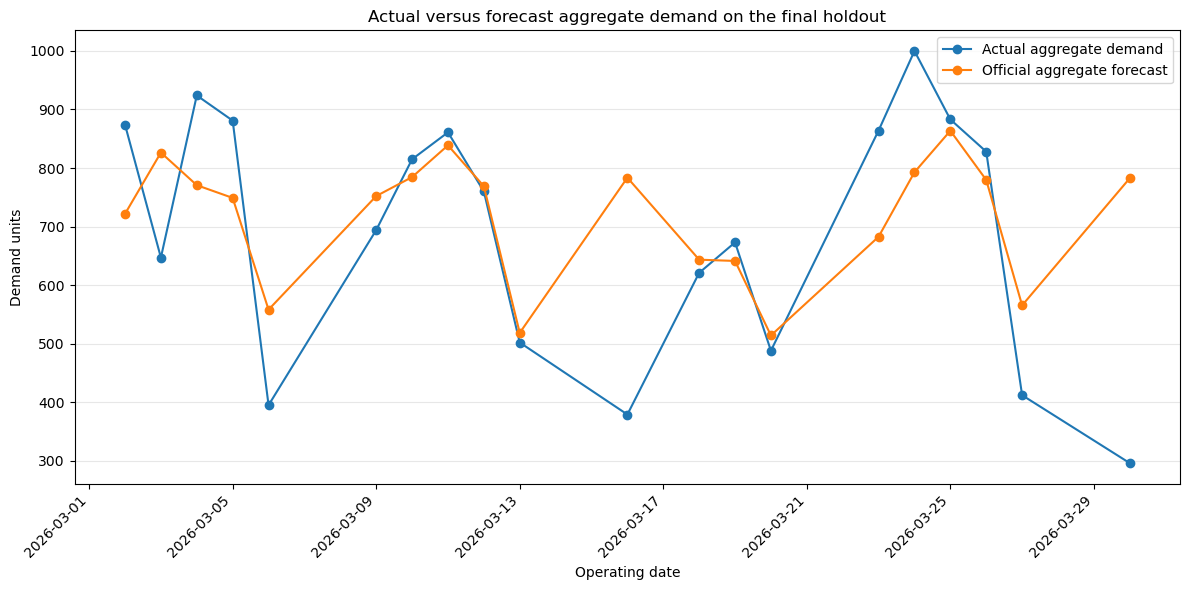

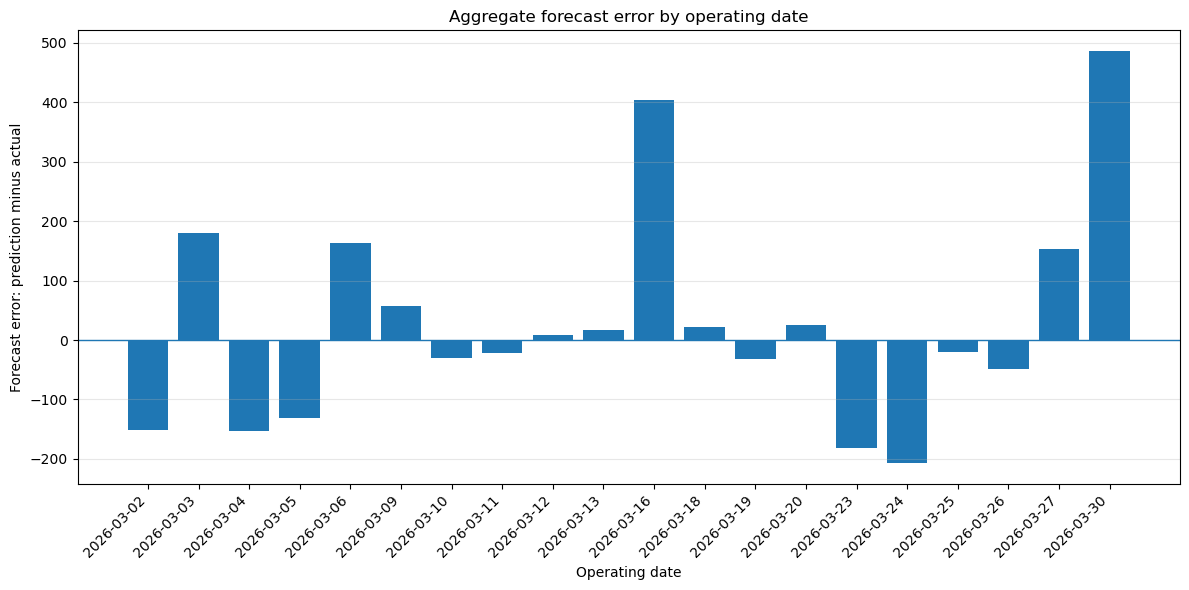

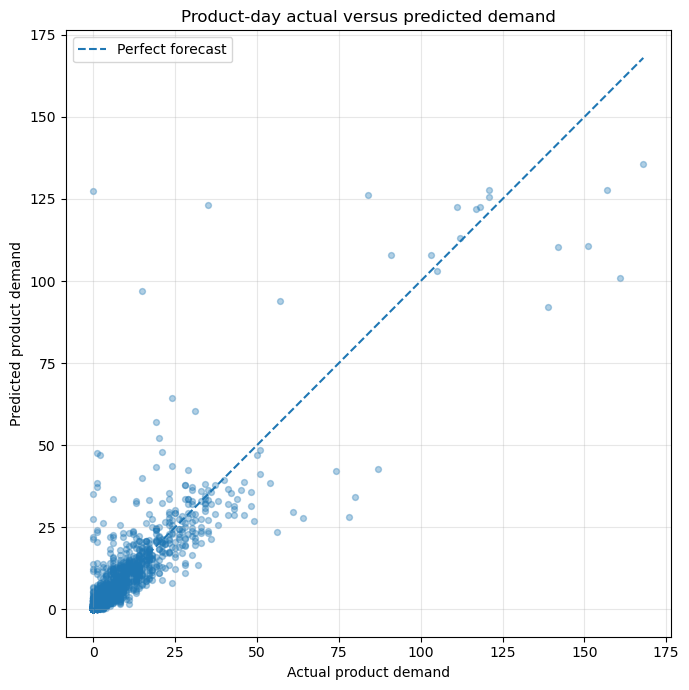

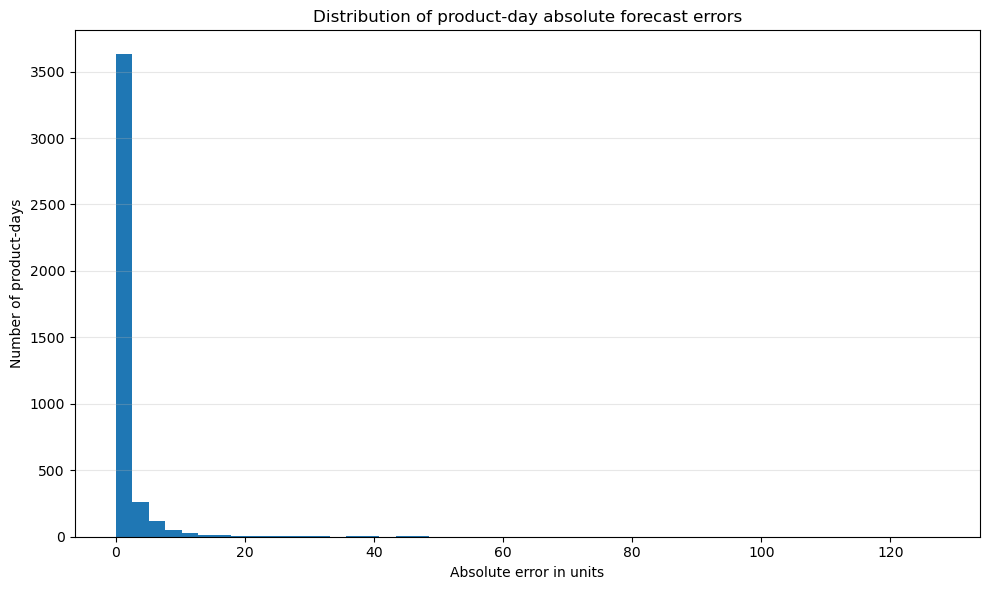

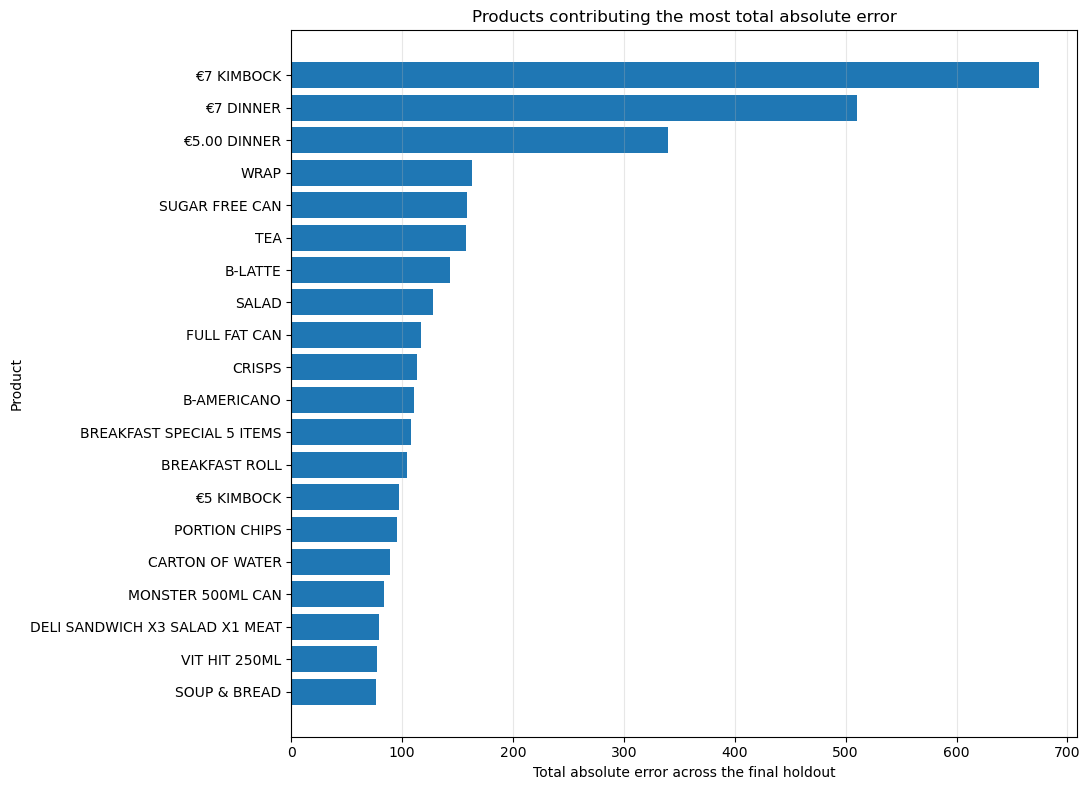

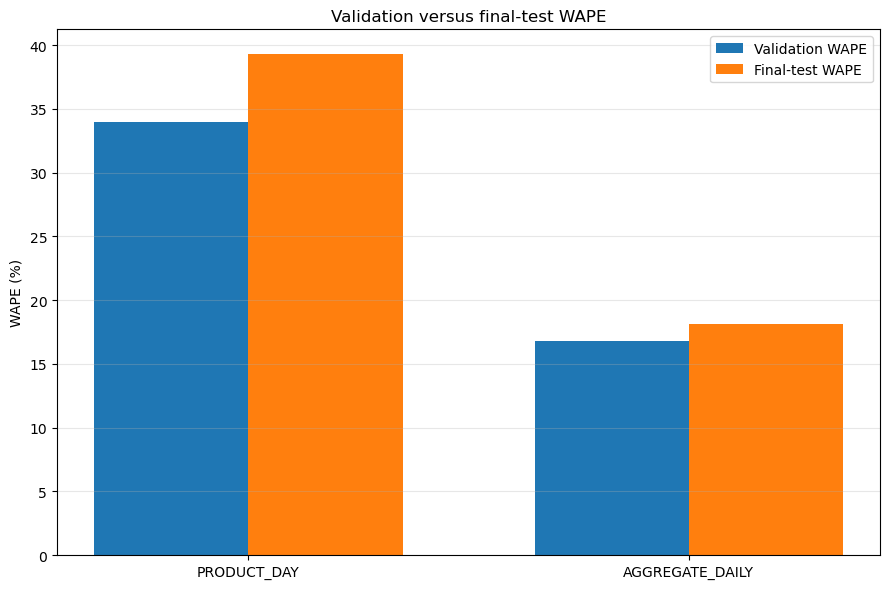

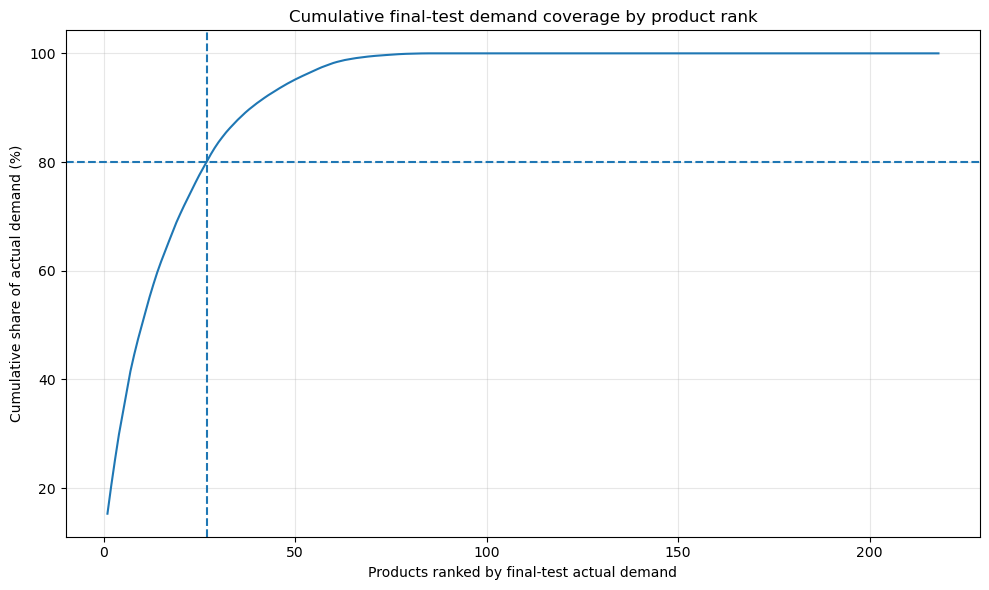

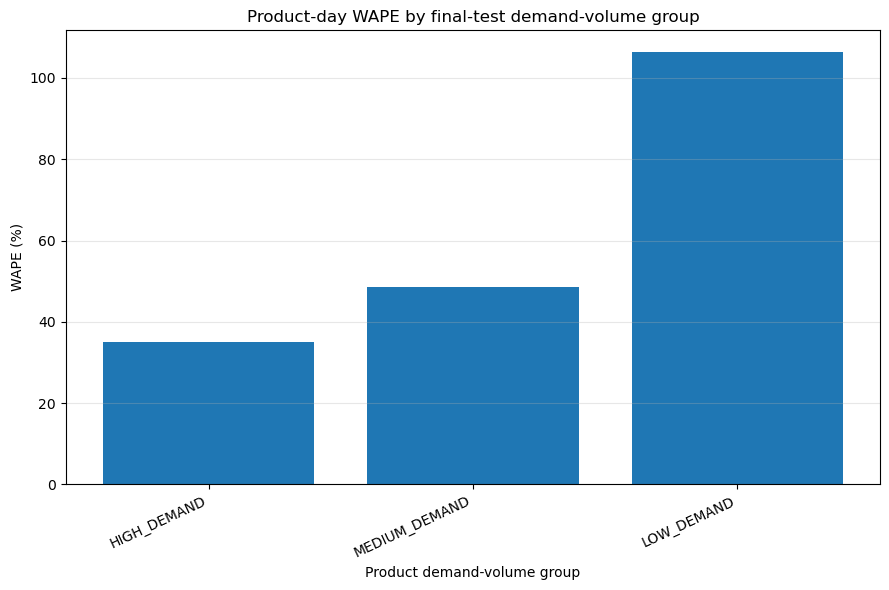


MODELLING STEP 4 PART 10D: FINAL_DIAGNOSTICS_AND_REPORT_READY_ARTIFACTS_SAVED_AND_HASHED

OFFICIAL FINAL-TEST METRICS:


,EvaluationLevel,MethodID,ObservationCount,ActualDemandTotal,PredictedDemandTotal,MAE,RMSE,WAPE_Percent,WAPE_Based_Forecast_Score_Percent,MeanBias,TotalBias,OverforecastUnits,UnderforecastUnits,ScoreWarning
0,PRODUCT_DAY,BLEND_HURDLE_NAIVE5__H75,4150,13797,14532.595485,1.305446,4.887817,39.266517,60.733483,0.177252,735.595485,3076.598402,2341.002917,DESCRIPTIVE_100_MINUS_WAPE_NOT_CONVENTIONAL_ACCURACY
1,AGGREGATE_DAILY,BLEND_HURDLE_HIST_GB__H50,20,13797,14337.844375,124.858031,177.870950,18.099301,81.900699,27.042219,540.844375,1519.002495,978.158120,DESCRIPTIVE_100_MINUS_WAPE_NOT_CONVENTIONAL_ACCURACY



WORST AGGREGATE DATES:


,Date,ActualAggregateDemand,AggregateForecast,AggregateForecastError,AggregateAbsoluteError,AbsolutePercentageError,ErrorDirection,ProductCount
19,2026-03-30,296,782.622157,486.622157,486.622157,164.399377,OVERFORECAST,218
10,2026-03-16,379,783.541148,404.541148,404.541148,106.739089,OVERFORECAST,204
15,2026-03-24,1000,792.810390,-207.189610,207.189610,20.718961,UNDERFORECAST,218
14,2026-03-23,864,682.611678,-181.388322,181.388322,20.994019,UNDERFORECAST,204
1,2026-03-03,647,826.398464,179.398464,179.398464,27.727738,OVERFORECAST,204
4,2026-03-06,395,558.084076,163.084076,163.084076,41.287108,OVERFORECAST,204
18,2026-03-27,412,565.418973,153.418973,153.418973,37.237615,OVERFORECAST,218
2,2026-03-04,924,770.701793,-153.298207,153.298207,16.590715,UNDERFORECAST,204
0,2026-03-02,874,721.711885,-152.288115,152.288115,17.424269,UNDERFORECAST,204
3,2026-03-05,881,748.972915,-132.027085,132.027085,14.986048,UNDERFORECAST,204



WORST PRODUCT-DAYS:


...


FORECAST-TOLERANCE DIAGNOSTICS:


,DiagnosticScope,ToleranceDefinition,ObservationCount,WithinToleranceCount,WithinTolerancePercent,IsOfficialMetric
0,ALL_PRODUCT_DAYS,ABSOLUTE_ERROR_LE_1_UNITS,4150,3180,76.626506,False
1,ALL_PRODUCT_DAYS,ABSOLUTE_ERROR_LE_2_UNITS,4150,3516,84.722892,False
2,ALL_PRODUCT_DAYS,ABSOLUTE_ERROR_LE_5_UNITS,4150,3886,93.638554,False
3,POSITIVE_DEMAND_PRODUCT_DAYS,ABSOLUTE_PERCENTAGE_ERROR_LE_20_PERCENT,1290,401,31.085271,False
4,POSITIVE_DEMAND_PRODUCT_DAYS,ABSOLUTE_PERCENTAGE_ERROR_LE_30_PERCENT,1290,573,44.418605,False
5,POSITIVE_DEMAND_PRODUCT_DAYS,ABSOLUTE_PERCENTAGE_ERROR_LE_50_PERCENT,1290,815,63.178295,False



VALIDATION SUMMARY:


,Check,Expected,Actual,Passed
0,Part 10C lock status,FINAL_HOLDOUT_EVALUATION_SAVED_AND_HASHED,FINAL_HOLDOUT_EVALUATION_SAVED_AND_HASHED,True
1,Part 10C lock SHA-256,95e23afaf3944f1b456ad9a90e99cb777d31812f2cc11708012b6a10143cb725,95e23afaf3944f1b456ad9a90e99cb777d31812f2cc11708012b6a10143cb725,True
2,Scored product rows,4150,4150,True
3,Scored aggregate dates,20,20,True
4,Evaluation products,218,218,True
5,Duplicate product-date rows,0,0,True
6,Duplicate aggregate dates,0,0,True
7,Official metric rows,2,2,True
8,Product diagnostic rows,218,218,True
9,Worst aggregate-date rows,10,10,True



Report figures saved: 8
Artifact hash failures: 0
Protected target vault opened by Part 10D: False
Models fitted in Part 10D: False
Predictions changed in Part 10D: False
Ready for final report writing: True
Diagnostic lock SHA-256: 4d4110b9d7a83ccaa382089f099a82f34834d2d75fd044e87449e23c6efbe337

Saved output folder:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/06_final_diagnostics_and_reporting/10D_report_ready_diagnostics

Main report-ready files:
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/06_final_diagnostics_and_reporting/10D_report_ready_diagnostics/10D_report_metric_table.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/06_final_diagnostics_and_reporting/10D_report_ready_diagnostics/10D_worst_aggregate_dates.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/06_final_diagnostics_and_reporting/10D_report_ready_diagnostics/10D_worst_product_days.csv
/Users/ryansmac/Desktop/Meng Project/eden_datasets/modelling/06_fina

In [72]:
# ==============================================================
# MODELLING STEP 4, PART 10D
# Final diagnostic analysis and report-ready results
#
# PURPOSE
# --------------------------------------------------------------
# - Verify the completed Part 10C final-evaluation lock.
# - Read only the already-scored Part 10C outputs.
# - Produce report-ready tables and diagnostic figures.
# - Identify worst dates, worst product-days and difficult products.
# - Compare actual and forecast demand visually.
# - Summarise demand concentration and core-product performance.
# - Calculate clearly defined forecast-tolerance diagnostics.
#
# IMPORTANT
# --------------------------------------------------------------
# - The protected target vault is NOT opened by this cell.
# - No model is fitted or changed.
# - No prediction is changed or rounded before analysis.
# - Product and aggregate methods remain separate.
# - WAPE remains an error metric, not conventional accuracy.
# ============================================================== 

from pathlib import Path
from datetime import datetime, timezone

import hashlib
import json
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display


# --------------------------------------------------------------
# 1. Paths
# --------------------------------------------------------------

EDEN_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

MODELLING_ROOT = EDEN_ROOT / "modelling"

PART10C_DIR = (
    MODELLING_ROOT
    / "05_final_refit_and_prediction"
    / "10C_final_holdout_evaluation"
)

PART10D_DIR = (
    MODELLING_ROOT
    / "06_final_diagnostics_and_reporting"
    / "10D_report_ready_diagnostics"
)

PART10D_DIR.mkdir(parents=True, exist_ok=True)

FINAL_LOCK_PATH = PART10C_DIR / "10C_final_evaluation_lock.json"
FINAL_LOCK_SHA_PATH = PART10C_DIR / "10C_final_evaluation_lock.sha256"

SCORED_PRODUCT_PATH = PART10C_DIR / "10C_scored_product_predictions.csv"
SCORED_AGGREGATE_PATH = PART10C_DIR / "10C_scored_aggregate_predictions.csv"
FINAL_METRIC_SUMMARY_PATH = PART10C_DIR / "10C_final_metric_summary.csv"
SEGMENT_METRICS_PATH = PART10C_DIR / "10C_product_segment_metrics.csv"
PRODUCT_LEVEL_METRICS_PATH = PART10C_DIR / "10C_product_level_metrics.csv"
PRODUCT_DATE_METRICS_PATH = PART10C_DIR / "10C_product_date_metrics.csv"
VALIDATION_COMPARISON_PATH = PART10C_DIR / "10C_validation_vs_final_comparison.csv"
FINAL_VALIDATION_PATH = PART10C_DIR / "10C_final_evaluation_validation_summary.csv"

PROJECT_CHECKPOINT_PATH = MODELLING_ROOT / "PROJECT_MODELLING_CHECKPOINT.md"

# Report-ready table outputs
REPORT_METRICS_PATH = PART10D_DIR / "10D_report_metric_table.csv"
WORST_DATES_PATH = PART10D_DIR / "10D_worst_aggregate_dates.csv"
BEST_DATES_PATH = PART10D_DIR / "10D_best_aggregate_dates.csv"
WORST_PRODUCT_DAYS_PATH = PART10D_DIR / "10D_worst_product_days.csv"
PRODUCT_DIAGNOSTIC_PATH = PART10D_DIR / "10D_product_diagnostic_summary.csv"
TOP_DEMAND_PRODUCTS_PATH = PART10D_DIR / "10D_top_products_by_actual_demand.csv"
DEMAND_CONCENTRATION_PATH = PART10D_DIR / "10D_demand_concentration_summary.csv"
CORE_PRODUCT_METRICS_PATH = PART10D_DIR / "10D_core_product_metrics.csv"
DEMAND_GROUP_METRICS_PATH = PART10D_DIR / "10D_demand_group_metrics.csv"
TOLERANCE_DIAGNOSTICS_PATH = PART10D_DIR / "10D_forecast_tolerance_diagnostics.csv"
REPORT_SUMMARY_PATH = PART10D_DIR / "10D_report_ready_summary.md"
VALIDATION_SUMMARY_PATH = PART10D_DIR / "10D_diagnostic_validation_summary.csv"

# Figures
FIGURE_01_PATH = PART10D_DIR / "10D_figure_01_aggregate_actual_vs_forecast.png"
FIGURE_02_PATH = PART10D_DIR / "10D_figure_02_aggregate_error_by_date.png"
FIGURE_03_PATH = PART10D_DIR / "10D_figure_03_product_actual_vs_predicted.png"
FIGURE_04_PATH = PART10D_DIR / "10D_figure_04_product_absolute_error_distribution.png"
FIGURE_05_PATH = PART10D_DIR / "10D_figure_05_worst_products_by_total_absolute_error.png"
FIGURE_06_PATH = PART10D_DIR / "10D_figure_06_validation_vs_final_wape.png"
FIGURE_07_PATH = PART10D_DIR / "10D_figure_07_cumulative_demand_coverage.png"
FIGURE_08_PATH = PART10D_DIR / "10D_figure_08_demand_group_wape.png"

ARTIFACT_MANIFEST_PATH = PART10D_DIR / "10D_artifact_hash_manifest.csv"
DIAGNOSTIC_LOCK_PATH = PART10D_DIR / "10D_diagnostic_lock.json"
DIAGNOSTIC_LOCK_SHA_PATH = PART10D_DIR / "10D_diagnostic_lock.sha256"
HANDOFF_PATH = PART10D_DIR / "MODELLING_STEP4_PART10D_HANDOFF.md"


# --------------------------------------------------------------
# 2. Contract constants
# --------------------------------------------------------------

TARGET = "TotalDemand"
DATE = "Date"
PRODUCT_ID = "CanonicalProductID"
PRODUCT_NAME = "CanonicalProductName"
PRODUCT_PREDICTION = "FinalProductPrediction"
AGGREGATE_PREDICTION = "AggregateForecast"
PRODUCT_BOTTOM_UP = "ProductMethodBottomUpTotal"

PRODUCT_METHOD = "BLEND_HURDLE_NAIVE5__H75"
AGGREGATE_METHOD = "BLEND_HURDLE_HIST_GB__H50"

EXPECTED_ROWS = 4150
EXPECTED_PRODUCTS = 218
EXPECTED_DATES = 20
EXPECTED_PART10C_STATUS = "FINAL_HOLDOUT_EVALUATION_SAVED_AND_HASHED"

# The core-product diagnostic includes the smallest ranked set whose
# cumulative actual demand reaches at least 80% of total demand.
CORE_DEMAND_SHARE_TARGET = 0.80

# Report sizes
NUMBER_OF_WORST_DATES = 10
NUMBER_OF_BEST_DATES = 5
NUMBER_OF_WORST_PRODUCT_DAYS = 30
NUMBER_OF_WORST_PRODUCTS = 20
NUMBER_OF_TOP_DEMAND_PRODUCTS = 30


# --------------------------------------------------------------
# 3. Overwrite guard
# --------------------------------------------------------------

if DIAGNOSTIC_LOCK_PATH.exists():
    raise FileExistsError(
        "Part 10D is already complete. The diagnostic lock exists:\n"
        f"{DIAGNOSTIC_LOCK_PATH}\n"
        "Do not overwrite report-ready diagnostic artifacts."
    )


# --------------------------------------------------------------
# 4. Helpers
# --------------------------------------------------------------

def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def atomic_csv(dataframe, path, float_format="%.10f"):
    temporary = path.with_suffix(path.suffix + ".tmp")
    dataframe.to_csv(
        temporary,
        index=False,
        float_format=float_format,
        date_format="%Y-%m-%d",
    )
    os.replace(temporary, path)


def atomic_json(payload, path):
    temporary = path.with_suffix(path.suffix + ".tmp")
    with open(temporary, "w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2, sort_keys=True, default=str)
        handle.write("\n")
    os.replace(temporary, path)


def atomic_text(text, path):
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(text, encoding="utf-8")
    os.replace(temporary, path)


def add_check(records, name, expected, actual, passed=None):
    if passed is None:
        passed = expected == actual
    records.append(
        {
            "Check": name,
            "Expected": str(expected),
            "Actual": str(actual),
            "Passed": bool(passed),
        }
    )


def forecast_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    if actual.ndim != 1 or predicted.ndim != 1:
        raise ValueError("Metric arrays must be one-dimensional.")
    if len(actual) != len(predicted):
        raise ValueError("Actual and predicted arrays differ in length.")
    if len(actual) == 0:
        raise ValueError("Cannot calculate metrics for zero observations.")
    if not np.isfinite(actual).all() or not np.isfinite(predicted).all():
        raise ValueError("Metric inputs contain non-finite values.")

    error = predicted - actual
    absolute_error = np.abs(error)
    actual_total = float(actual.sum())
    predicted_total = float(predicted.sum())

    if np.isclose(actual_total, 0.0, rtol=1e-12, atol=1e-12):
        wape = np.nan
    else:
        wape = float(absolute_error.sum() / actual_total * 100.0)

    return {
        "ObservationCount": int(len(actual)),
        "ActualDemandTotal": actual_total,
        "PredictedDemandTotal": predicted_total,
        "MAE": float(absolute_error.mean()),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "WAPE_Percent": wape,
        "MeanBias": float(error.mean()),
        "TotalBias": float(error.sum()),
        "OverforecastUnits": float(np.clip(error, 0.0, None).sum()),
        "UnderforecastUnits": float(np.clip(-error, 0.0, None).sum()),
        "ZeroActualObservationCount": int(np.isclose(actual, 0.0).sum()),
    }


def save_current_figure(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def safe_name_series(dataframe):
    if PRODUCT_NAME in dataframe.columns:
        result = dataframe[PRODUCT_NAME].fillna("").astype(str)
        missing = result.str.strip().eq("")
        result.loc[missing] = dataframe.loc[missing, PRODUCT_ID].astype(str)
        return result
    return dataframe[PRODUCT_ID].astype(str)


# --------------------------------------------------------------
# 5. Verify required inputs
# --------------------------------------------------------------

required_paths = [
    FINAL_LOCK_PATH,
    FINAL_LOCK_SHA_PATH,
    SCORED_PRODUCT_PATH,
    SCORED_AGGREGATE_PATH,
    FINAL_METRIC_SUMMARY_PATH,
    SEGMENT_METRICS_PATH,
    PRODUCT_LEVEL_METRICS_PATH,
    PRODUCT_DATE_METRICS_PATH,
    VALIDATION_COMPARISON_PATH,
    FINAL_VALIDATION_PATH,
]

missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing required Part 10C artifacts:\n"
        + "\n".join(str(path) for path in missing_paths)
    )

with open(FINAL_LOCK_PATH, "r", encoding="utf-8") as handle:
    final_lock = json.load(handle)

actual_final_lock_hash = sha256_file(FINAL_LOCK_PATH)
sidecar_text = FINAL_LOCK_SHA_PATH.read_text(encoding="utf-8").strip()
sidecar_final_lock_hash = sidecar_text.split()[0] if sidecar_text else ""

if actual_final_lock_hash != sidecar_final_lock_hash:
    raise AssertionError("Part 10C final-evaluation lock hash mismatch.")

if final_lock.get("Status") != EXPECTED_PART10C_STATUS:
    raise AssertionError("Part 10C final-evaluation status is not complete.")

if not bool(final_lock.get("ReadyForFinalReporting", False)):
    raise AssertionError("Part 10C is not marked ready for final reporting.")

if bool(final_lock.get("PredictionsChangedAfterLock", True)):
    raise AssertionError("The Part 10C lock reports changed predictions.")

if bool(final_lock.get("ModelsRefittedInPart10C", True)):
    raise AssertionError("The Part 10C lock reports model refitting.")


# --------------------------------------------------------------
# 6. Load already-scored outputs only
# --------------------------------------------------------------

scored_product = pd.read_csv(SCORED_PRODUCT_PATH, low_memory=False)
scored_aggregate = pd.read_csv(SCORED_AGGREGATE_PATH, low_memory=False)
final_metrics = pd.read_csv(FINAL_METRIC_SUMMARY_PATH)
segment_metrics = pd.read_csv(SEGMENT_METRICS_PATH)
part10c_product_metrics = pd.read_csv(PRODUCT_LEVEL_METRICS_PATH)
product_date_metrics = pd.read_csv(PRODUCT_DATE_METRICS_PATH)
validation_comparison = pd.read_csv(VALIDATION_COMPARISON_PATH)
part10c_validation = pd.read_csv(FINAL_VALIDATION_PATH)

scored_product[DATE] = pd.to_datetime(scored_product[DATE], errors="raise")
scored_aggregate[DATE] = pd.to_datetime(scored_aggregate[DATE], errors="raise")
product_date_metrics[DATE] = pd.to_datetime(product_date_metrics[DATE], errors="raise")

scored_product[PRODUCT_ID] = scored_product[PRODUCT_ID].astype(str)
scored_product["DisplayProductName"] = safe_name_series(scored_product)

required_product_columns = [
    DATE,
    PRODUCT_ID,
    TARGET,
    PRODUCT_PREDICTION,
    "ForecastError",
    "AbsoluteError",
    "SquaredError",
]
required_aggregate_columns = [
    DATE,
    "ActualAggregateDemand",
    AGGREGATE_PREDICTION,
    PRODUCT_BOTTOM_UP,
    "AggregateForecastError",
    "AggregateAbsoluteError",
]

missing_product_columns = [
    column for column in required_product_columns if column not in scored_product.columns
]
missing_aggregate_columns = [
    column for column in required_aggregate_columns if column not in scored_aggregate.columns
]

if missing_product_columns:
    raise KeyError(f"Scored product output is missing: {missing_product_columns}")
if missing_aggregate_columns:
    raise KeyError(f"Scored aggregate output is missing: {missing_aggregate_columns}")


# --------------------------------------------------------------
# 7. Verify the scored files against the Part 10C lock
# --------------------------------------------------------------

locked_product_output = final_lock["ScoredOutputs"]["Product"]
locked_aggregate_output = final_lock["ScoredOutputs"]["Aggregate"]

if sha256_file(SCORED_PRODUCT_PATH) != locked_product_output["SHA256"]:
    raise AssertionError("Scored product output hash mismatch.")

if sha256_file(SCORED_AGGREGATE_PATH) != locked_aggregate_output["SHA256"]:
    raise AssertionError("Scored aggregate output hash mismatch.")


# --------------------------------------------------------------
# 8. Official report metric table
# --------------------------------------------------------------

official_metric_mask = final_metrics["IsOfficialMetric"].map(
    lambda value: str(value).strip().lower() in {"true", "1", "yes"}
)
official_metrics = final_metrics.loc[official_metric_mask].copy()

official_metrics["WAPE_Based_Forecast_Score_Percent"] = (
    100.0 - official_metrics["WAPE_Percent"].astype(float)
)
official_metrics["ScoreWarning"] = (
    "DESCRIPTIVE_100_MINUS_WAPE_NOT_CONVENTIONAL_ACCURACY"
)

report_metric_columns = [
    "EvaluationLevel",
    "MethodID",
    "ObservationCount",
    "ActualDemandTotal",
    "PredictedDemandTotal",
    "MAE",
    "RMSE",
    "WAPE_Percent",
    "WAPE_Based_Forecast_Score_Percent",
    "MeanBias",
    "TotalBias",
    "OverforecastUnits",
    "UnderforecastUnits",
    "ScoreWarning",
]
report_metrics = official_metrics[report_metric_columns].copy()


# --------------------------------------------------------------
# 9. Worst-date and best-date tables
# --------------------------------------------------------------

worst_dates = scored_aggregate.sort_values(
    "AggregateAbsoluteError",
    ascending=False,
    kind="mergesort",
).head(NUMBER_OF_WORST_DATES).copy()

worst_dates["AbsolutePercentageError"] = np.where(
    worst_dates["ActualAggregateDemand"].to_numpy(dtype=float) > 0,
    worst_dates["AggregateAbsoluteError"].to_numpy(dtype=float)
    / worst_dates["ActualAggregateDemand"].to_numpy(dtype=float)
    * 100.0,
    np.nan,
)
worst_dates["ErrorDirection"] = np.where(
    worst_dates["AggregateForecastError"] > 0,
    "OVERFORECAST",
    np.where(
        worst_dates["AggregateForecastError"] < 0,
        "UNDERFORECAST",
        "EXACT",
    ),
)

worst_date_columns = [
    DATE,
    "ActualAggregateDemand",
    AGGREGATE_PREDICTION,
    "AggregateForecastError",
    "AggregateAbsoluteError",
    "AbsolutePercentageError",
    "ErrorDirection",
    "ProductCount",
]
worst_dates = worst_dates[worst_date_columns]

best_dates = scored_aggregate.sort_values(
    "AggregateAbsoluteError",
    ascending=True,
    kind="mergesort",
).head(NUMBER_OF_BEST_DATES).copy()

best_dates["AbsolutePercentageError"] = np.where(
    best_dates["ActualAggregateDemand"].to_numpy(dtype=float) > 0,
    best_dates["AggregateAbsoluteError"].to_numpy(dtype=float)
    / best_dates["ActualAggregateDemand"].to_numpy(dtype=float)
    * 100.0,
    np.nan,
)
best_dates["ErrorDirection"] = np.where(
    best_dates["AggregateForecastError"] > 0,
    "OVERFORECAST",
    np.where(
        best_dates["AggregateForecastError"] < 0,
        "UNDERFORECAST",
        "EXACT",
    ),
)
best_dates = best_dates[worst_date_columns]


# --------------------------------------------------------------
# 10. Worst product-day table
# --------------------------------------------------------------

worst_product_days = scored_product.sort_values(
    "AbsoluteError",
    ascending=False,
    kind="mergesort",
).head(NUMBER_OF_WORST_PRODUCT_DAYS).copy()

worst_product_days["ErrorDirection"] = np.where(
    worst_product_days["ForecastError"] > 0,
    "OVERFORECAST",
    np.where(worst_product_days["ForecastError"] < 0, "UNDERFORECAST", "EXACT"),
)
worst_product_days["AbsolutePercentageError"] = np.where(
    worst_product_days[TARGET].to_numpy(dtype=float) > 0,
    worst_product_days["AbsoluteError"].to_numpy(dtype=float)
    / worst_product_days[TARGET].to_numpy(dtype=float)
    * 100.0,
    np.nan,
)

worst_product_day_columns = [
    DATE,
    PRODUCT_ID,
    "DisplayProductName",
    TARGET,
    PRODUCT_PREDICTION,
    "ForecastError",
    "AbsoluteError",
    "AbsolutePercentageError",
    "ErrorDirection",
]
worst_product_days = worst_product_days[worst_product_day_columns]


# --------------------------------------------------------------
# 11. Product-level diagnostic table
# --------------------------------------------------------------

product_records = []
for product_id, group in scored_product.groupby(PRODUCT_ID, sort=True):
    product_name = group["DisplayProductName"].iloc[0]
    metrics = forecast_metrics(group[TARGET], group[PRODUCT_PREDICTION])
    actual = group[TARGET].to_numpy(dtype=float)
    predicted = group[PRODUCT_PREDICTION].to_numpy(dtype=float)
    error = predicted - actual
    positive_mask = actual > 0

    positive_day_count = int(positive_mask.sum())
    zero_day_count = int((~positive_mask).sum())
    observed_day_count = int(len(group))

    if positive_day_count:
        positive_mae = float(np.abs(error[positive_mask]).mean())
        positive_actual_total = float(actual[positive_mask].sum())
        positive_wape = float(
            np.abs(error[positive_mask]).sum() / positive_actual_total * 100.0
        )
    else:
        positive_mae = np.nan
        positive_wape = np.nan

    product_records.append(
        {
            PRODUCT_ID: product_id,
            PRODUCT_NAME: product_name,
            **metrics,
            "ObservedDayCount": observed_day_count,
            "PositiveDemandDayCount": positive_day_count,
            "ZeroDemandDayCount": zero_day_count,
            "PositiveDemandDayRate_Percent": (
                positive_day_count / observed_day_count * 100.0
            ),
            "ZeroDemandDayRate_Percent": zero_day_count / observed_day_count * 100.0,
            "PositiveDemandMAE": positive_mae,
            "PositiveDemandWAPE_Percent": positive_wape,
            "MaximumAbsoluteError": float(np.abs(error).max()),
            "MedianAbsoluteError": float(np.median(np.abs(error))),
            "WithinOneUnitCount": int((np.abs(error) <= 1.0).sum()),
            "WithinTwoUnitsCount": int((np.abs(error) <= 2.0).sum()),
            "WithinFiveUnitsCount": int((np.abs(error) <= 5.0).sum()),
            "WithinOneUnitRate_Percent": float((np.abs(error) <= 1.0).mean() * 100.0),
            "WithinTwoUnitsRate_Percent": float((np.abs(error) <= 2.0).mean() * 100.0),
            "WithinFiveUnitsRate_Percent": float((np.abs(error) <= 5.0).mean() * 100.0),
        }
    )

product_diagnostics = pd.DataFrame(product_records)
product_diagnostics = product_diagnostics.sort_values(
    ["ActualDemandTotal", PRODUCT_ID],
    ascending=[False, True],
    kind="mergesort",
).reset_index(drop=True)

actual_total_all_products = float(product_diagnostics["ActualDemandTotal"].sum())
if actual_total_all_products <= 0:
    raise AssertionError("Total actual demand is not positive.")

product_diagnostics["ActualDemandShare_Percent"] = (
    product_diagnostics["ActualDemandTotal"] / actual_total_all_products * 100.0
)
product_diagnostics["CumulativeActualDemandShare_Percent"] = (
    product_diagnostics["ActualDemandShare_Percent"].cumsum()
)

# Include the first product that crosses the 80% threshold.
threshold_reached = (
    product_diagnostics["CumulativeActualDemandShare_Percent"]
    >= CORE_DEMAND_SHARE_TARGET * 100.0
)
if threshold_reached.any():
    core_last_position = int(np.flatnonzero(threshold_reached.to_numpy())[0])
else:
    core_last_position = len(product_diagnostics) - 1

product_diagnostics["CoreDemandProduct"] = False
product_diagnostics.loc[:core_last_position, "CoreDemandProduct"] = True
product_diagnostics["DemandRank"] = np.arange(1, len(product_diagnostics) + 1)

# Demand-volume groups are descriptive final-test diagnostics only.
positive_total_mask = product_diagnostics["ActualDemandTotal"] > 0
positive_totals = product_diagnostics.loc[positive_total_mask, "ActualDemandTotal"]

if positive_totals.nunique() >= 3:
    lower_cut = float(positive_totals.quantile(1 / 3))
    upper_cut = float(positive_totals.quantile(2 / 3))
else:
    lower_cut = float(positive_totals.min()) if len(positive_totals) else 0.0
    upper_cut = float(positive_totals.max()) if len(positive_totals) else 0.0

product_diagnostics["DemandVolumeGroup"] = np.select(
    [
        product_diagnostics["ActualDemandTotal"] <= 0,
        product_diagnostics["ActualDemandTotal"] <= lower_cut,
        product_diagnostics["ActualDemandTotal"] <= upper_cut,
    ],
    [
        "NO_FINAL_TEST_DEMAND",
        "LOW_DEMAND",
        "MEDIUM_DEMAND",
    ],
    default="HIGH_DEMAND",
)


# --------------------------------------------------------------
# 12. Demand concentration and core-product metrics
# --------------------------------------------------------------

core_products = product_diagnostics.loc[
    product_diagnostics["CoreDemandProduct"]
].copy()

core_product_ids = set(core_products[PRODUCT_ID].astype(str))
core_product_rows = scored_product.loc[
    scored_product[PRODUCT_ID].astype(str).isin(core_product_ids)
].copy()

non_core_product_rows = scored_product.loc[
    ~scored_product[PRODUCT_ID].astype(str).isin(core_product_ids)
].copy()

core_metrics = forecast_metrics(
    core_product_rows[TARGET],
    core_product_rows[PRODUCT_PREDICTION],
)
non_core_metrics = forecast_metrics(
    non_core_product_rows[TARGET],
    non_core_product_rows[PRODUCT_PREDICTION],
)

core_product_metrics = pd.DataFrame(
    [
        {
            "Segment": "CORE_PRODUCTS_REACHING_AT_LEAST_80_PERCENT_DEMAND",
            "ProductCount": int(core_products[PRODUCT_ID].nunique()),
            "DemandSharePercent": float(
                core_product_rows[TARGET].sum() / scored_product[TARGET].sum() * 100.0
            ),
            **core_metrics,
        },
        {
            "Segment": "REMAINING_PRODUCTS",
            "ProductCount": int(
                product_diagnostics[PRODUCT_ID].nunique()
                - core_products[PRODUCT_ID].nunique()
            ),
            "DemandSharePercent": float(
                non_core_product_rows[TARGET].sum()
                / scored_product[TARGET].sum()
                * 100.0
            ),
            **non_core_metrics,
        },
    ]
)

concentration_records = []
for share_target in [0.50, 0.80, 0.90, 0.95]:
    reached = (
        product_diagnostics["CumulativeActualDemandShare_Percent"]
        >= share_target * 100.0
    )
    if reached.any():
        last_position = int(np.flatnonzero(reached.to_numpy())[0])
        product_count = last_position + 1
        achieved_share = float(
            product_diagnostics.loc[
                last_position,
                "CumulativeActualDemandShare_Percent",
            ]
        )
    else:
        product_count = len(product_diagnostics)
        achieved_share = 100.0

    concentration_records.append(
        {
            "DemandShareTargetPercent": share_target * 100.0,
            "MinimumProductCount": product_count,
            "ShareOfAllProductsPercent": (
                product_count / len(product_diagnostics) * 100.0
            ),
            "ActualDemandShareAchievedPercent": achieved_share,
        }
    )

demand_concentration = pd.DataFrame(concentration_records)


# --------------------------------------------------------------
# 13. Demand-volume group metrics
# --------------------------------------------------------------

demand_group_records = []
for demand_group, product_group in product_diagnostics.groupby(
    "DemandVolumeGroup", sort=False
):
    product_ids = set(product_group[PRODUCT_ID].astype(str))
    rows = scored_product.loc[
        scored_product[PRODUCT_ID].astype(str).isin(product_ids)
    ]
    metrics = forecast_metrics(rows[TARGET], rows[PRODUCT_PREDICTION])
    demand_group_records.append(
        {
            "DemandVolumeGroup": demand_group,
            "ProductCount": int(product_group[PRODUCT_ID].nunique()),
            "DemandSharePercent": float(
                rows[TARGET].sum() / scored_product[TARGET].sum() * 100.0
            ),
            **metrics,
        }
    )

demand_group_metrics = pd.DataFrame(demand_group_records)

group_order = {
    "HIGH_DEMAND": 0,
    "MEDIUM_DEMAND": 1,
    "LOW_DEMAND": 2,
    "NO_FINAL_TEST_DEMAND": 3,
}
demand_group_metrics["GroupOrder"] = demand_group_metrics[
    "DemandVolumeGroup"
].map(group_order)
demand_group_metrics = demand_group_metrics.sort_values(
    "GroupOrder", kind="mergesort"
).drop(columns="GroupOrder").reset_index(drop=True)


# --------------------------------------------------------------
# 14. Clearly defined forecast-tolerance diagnostics
# --------------------------------------------------------------

actual_product = scored_product[TARGET].to_numpy(dtype=float)
predicted_product = scored_product[PRODUCT_PREDICTION].to_numpy(dtype=float)
absolute_error_product = np.abs(predicted_product - actual_product)
positive_mask = actual_product > 0

positive_relative_error = (
    absolute_error_product[positive_mask] / actual_product[positive_mask]
)

tolerance_records = []

for threshold in [1.0, 2.0, 5.0]:
    within = absolute_error_product <= threshold
    tolerance_records.append(
        {
            "DiagnosticScope": "ALL_PRODUCT_DAYS",
            "ToleranceDefinition": f"ABSOLUTE_ERROR_LE_{threshold:g}_UNITS",
            "ObservationCount": int(len(within)),
            "WithinToleranceCount": int(within.sum()),
            "WithinTolerancePercent": float(within.mean() * 100.0),
            "IsOfficialMetric": False,
        }
    )

for threshold in [0.20, 0.30, 0.50]:
    within = positive_relative_error <= threshold
    tolerance_records.append(
        {
            "DiagnosticScope": "POSITIVE_DEMAND_PRODUCT_DAYS",
            "ToleranceDefinition": (
                f"ABSOLUTE_PERCENTAGE_ERROR_LE_{threshold * 100:.0f}_PERCENT"
            ),
            "ObservationCount": int(len(within)),
            "WithinToleranceCount": int(within.sum()),
            "WithinTolerancePercent": float(within.mean() * 100.0),
            "IsOfficialMetric": False,
        }
    )

tolerance_diagnostics = pd.DataFrame(tolerance_records)


# --------------------------------------------------------------
# 15. Top-demand product table
# --------------------------------------------------------------

top_demand_products = product_diagnostics.head(
    NUMBER_OF_TOP_DEMAND_PRODUCTS
).copy()


# --------------------------------------------------------------
# 16. Generate report-ready figures
# --------------------------------------------------------------

# Figure 1: actual versus official aggregate forecast
plt.figure(figsize=(12, 6))
plt.plot(
    scored_aggregate[DATE],
    scored_aggregate["ActualAggregateDemand"],
    marker="o",
    label="Actual aggregate demand",
)
plt.plot(
    scored_aggregate[DATE],
    scored_aggregate[AGGREGATE_PREDICTION],
    marker="o",
    label="Official aggregate forecast",
)
plt.xlabel("Operating date")
plt.ylabel("Demand units")
plt.title("Actual versus forecast aggregate demand on the final holdout")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(axis="y", alpha=0.3)
save_current_figure(FIGURE_01_PATH)

# Figure 2: signed aggregate error by date
plt.figure(figsize=(12, 6))
plt.bar(
    scored_aggregate[DATE].dt.strftime("%Y-%m-%d"),
    scored_aggregate["AggregateForecastError"],
)
plt.axhline(0.0, linewidth=1)
plt.xlabel("Operating date")
plt.ylabel("Forecast error: prediction minus actual")
plt.title("Aggregate forecast error by operating date")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
save_current_figure(FIGURE_02_PATH)

# Figure 3: product-day actual versus predicted
plt.figure(figsize=(7, 7))
plt.scatter(
    scored_product[TARGET],
    scored_product[PRODUCT_PREDICTION],
    alpha=0.35,
    s=18,
)
plot_limit = float(
    max(
        scored_product[TARGET].max(),
        scored_product[PRODUCT_PREDICTION].max(),
    )
)
plt.plot([0, plot_limit], [0, plot_limit], linestyle="--", label="Perfect forecast")
plt.xlabel("Actual product demand")
plt.ylabel("Predicted product demand")
plt.title("Product-day actual versus predicted demand")
plt.legend()
plt.grid(alpha=0.3)
save_current_figure(FIGURE_03_PATH)

# Figure 4: product-day absolute-error distribution
plt.figure(figsize=(10, 6))
plt.hist(scored_product["AbsoluteError"], bins=50)
plt.xlabel("Absolute error in units")
plt.ylabel("Number of product-days")
plt.title("Distribution of product-day absolute forecast errors")
plt.grid(axis="y", alpha=0.3)
save_current_figure(FIGURE_04_PATH)

# Figure 5: products with the largest total absolute error
worst_products = product_diagnostics.sort_values(
    "OverforecastUnits",
    ascending=False,
    kind="mergesort",
).copy()
# Rank by total absolute error, which equals overforecast + underforecast units.
worst_products["TotalAbsoluteError"] = (
    worst_products["OverforecastUnits"] + worst_products["UnderforecastUnits"]
)
worst_products = worst_products.sort_values(
    "TotalAbsoluteError", ascending=False, kind="mergesort"
).head(NUMBER_OF_WORST_PRODUCTS)

plt.figure(figsize=(11, 8))
plt.barh(
    worst_products[PRODUCT_NAME].iloc[::-1],
    worst_products["TotalAbsoluteError"].iloc[::-1],
)
plt.xlabel("Total absolute error across the final holdout")
plt.ylabel("Product")
plt.title("Products contributing the most total absolute error")
plt.grid(axis="x", alpha=0.3)
save_current_figure(FIGURE_05_PATH)

# Figure 6: validation versus final-test WAPE
wape_comparison = validation_comparison.loc[
    validation_comparison["Metric"].astype(str) == "WAPE_Percent"
].copy()

wape_labels = wape_comparison["SelectionLevel"].astype(str).tolist()
x_positions = np.arange(len(wape_labels))
bar_width = 0.35

plt.figure(figsize=(9, 6))
plt.bar(
    x_positions - bar_width / 2,
    wape_comparison["ValidationValue"],
    width=bar_width,
    label="Validation WAPE",
)
plt.bar(
    x_positions + bar_width / 2,
    wape_comparison["FinalTestValue"],
    width=bar_width,
    label="Final-test WAPE",
)
plt.xticks(x_positions, wape_labels)
plt.ylabel("WAPE (%)")
plt.title("Validation versus final-test WAPE")
plt.legend()
plt.grid(axis="y", alpha=0.3)
save_current_figure(FIGURE_06_PATH)

# Figure 7: cumulative demand coverage by ranked product
plt.figure(figsize=(10, 6))
plt.plot(
    product_diagnostics["DemandRank"],
    product_diagnostics["CumulativeActualDemandShare_Percent"],
)
plt.axhline(CORE_DEMAND_SHARE_TARGET * 100.0, linestyle="--")
plt.axvline(core_last_position + 1, linestyle="--")
plt.xlabel("Products ranked by final-test actual demand")
plt.ylabel("Cumulative share of actual demand (%)")
plt.title("Cumulative final-test demand coverage by product rank")
plt.grid(alpha=0.3)
save_current_figure(FIGURE_07_PATH)

# Figure 8: WAPE by demand-volume group
plot_group_metrics = demand_group_metrics.loc[
    demand_group_metrics["WAPE_Percent"].notna()
].copy()

plt.figure(figsize=(9, 6))
plt.bar(
    plot_group_metrics["DemandVolumeGroup"],
    plot_group_metrics["WAPE_Percent"],
)
plt.xlabel("Product demand-volume group")
plt.ylabel("WAPE (%)")
plt.title("Product-day WAPE by final-test demand-volume group")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
save_current_figure(FIGURE_08_PATH)


# --------------------------------------------------------------
# 17. Save report-ready tables
# --------------------------------------------------------------

atomic_csv(report_metrics, REPORT_METRICS_PATH)
atomic_csv(worst_dates, WORST_DATES_PATH)
atomic_csv(best_dates, BEST_DATES_PATH)
atomic_csv(worst_product_days, WORST_PRODUCT_DAYS_PATH)
atomic_csv(product_diagnostics, PRODUCT_DIAGNOSTIC_PATH)
atomic_csv(top_demand_products, TOP_DEMAND_PRODUCTS_PATH)
atomic_csv(demand_concentration, DEMAND_CONCENTRATION_PATH)
atomic_csv(core_product_metrics, CORE_PRODUCT_METRICS_PATH)
atomic_csv(demand_group_metrics, DEMAND_GROUP_METRICS_PATH)
atomic_csv(tolerance_diagnostics, TOLERANCE_DIAGNOSTICS_PATH)


# --------------------------------------------------------------
# 18. Build report-ready written summary
# --------------------------------------------------------------

product_official = report_metrics.loc[
    report_metrics["EvaluationLevel"] == "PRODUCT_DAY"
].iloc[0]
aggregate_official = report_metrics.loc[
    report_metrics["EvaluationLevel"] == "AGGREGATE_DAILY"
].iloc[0]

worst_date_row = worst_dates.iloc[0]
core_row = core_product_metrics.loc[
    core_product_metrics["Segment"]
    == "CORE_PRODUCTS_REACHING_AT_LEAST_80_PERCENT_DEMAND"
].iloc[0]

within_two_units = tolerance_diagnostics.loc[
    tolerance_diagnostics["ToleranceDefinition"] == "ABSOLUTE_ERROR_LE_2_UNITS"
].iloc[0]
within_five_units = tolerance_diagnostics.loc[
    tolerance_diagnostics["ToleranceDefinition"] == "ABSOLUTE_ERROR_LE_5_UNITS"
].iloc[0]
within_thirty_percent = tolerance_diagnostics.loc[
    tolerance_diagnostics["ToleranceDefinition"]
    == "ABSOLUTE_PERCENTAGE_ERROR_LE_30_PERCENT"
].iloc[0]

summary_text = f"""# Part 10D — Final Diagnostic Analysis and Report-Ready Results

## Official final-test results

The locked product-day method `{PRODUCT_METHOD}` achieved:

- MAE: {product_official['MAE']:.3f} units per product-day
- RMSE: {product_official['RMSE']:.3f} units
- WAPE: {product_official['WAPE_Percent']:.2f}%
- Mean bias: {product_official['MeanBias']:.3f} units per product-day

The separate locked aggregate-daily method `{AGGREGATE_METHOD}` achieved:

- MAE: {aggregate_official['MAE']:.2f} units per operating day
- RMSE: {aggregate_official['RMSE']:.2f} units
- WAPE: {aggregate_official['WAPE_Percent']:.2f}%
- Mean bias: {aggregate_official['MeanBias']:.2f} units per day

The descriptive 100-minus-WAPE figures are {product_official['WAPE_Based_Forecast_Score_Percent']:.2f}% at product-day level and {aggregate_official['WAPE_Based_Forecast_Score_Percent']:.2f}% at aggregate-daily level. These are not conventional accuracy measures.

## Error diagnostics

The largest aggregate absolute error occurred on {worst_date_row[DATE].strftime('%Y-%m-%d')}. Actual aggregate demand was {worst_date_row['ActualAggregateDemand']:.0f} units and the forecast was {worst_date_row[AGGREGATE_PREDICTION]:.2f} units, producing an error of {worst_date_row['AggregateForecastError']:.2f} units.

Across all 4,150 product-day observations:

- {within_two_units['WithinTolerancePercent']:.2f}% were within plus or minus 2 units.
- {within_five_units['WithinTolerancePercent']:.2f}% were within plus or minus 5 units.
- Among positive-demand product-days, {within_thirty_percent['WithinTolerancePercent']:.2f}% were within plus or minus 30% of actual demand.

These tolerance results are diagnostic definitions rather than official forecasting metrics.

## Demand concentration and core products

{int(core_row['ProductCount'])} products were required to cover at least 80% of actual final-test demand. They represented {core_row['DemandSharePercent']:.2f}% of demand and achieved a WAPE of {core_row['WAPE_Percent']:.2f}%.

This concentration analysis is useful for ingredient mapping because it identifies the smaller set of products accounting for most demand. It is a final-test diagnostic only and was not used to retune the model.

## Interpretation

The system forecasts total daily demand more reliably than exact individual product quantities. Individual-product errors are concentrated in a smaller number of high-error product-days and products. The report should present MAE, RMSE, WAPE and bias as the official measures, with tolerance percentages and 100-minus-WAPE shown only as clearly labelled descriptive diagnostics.
"""

atomic_text(summary_text, REPORT_SUMMARY_PATH)


# --------------------------------------------------------------
# 19. Validation checks
# --------------------------------------------------------------

validation_records = []

add_check(validation_records, "Part 10C lock status", EXPECTED_PART10C_STATUS, final_lock.get("Status"))
add_check(validation_records, "Part 10C lock SHA-256", sidecar_final_lock_hash, actual_final_lock_hash)
add_check(validation_records, "Scored product rows", EXPECTED_ROWS, len(scored_product))
add_check(validation_records, "Scored aggregate dates", EXPECTED_DATES, len(scored_aggregate))
add_check(validation_records, "Evaluation products", EXPECTED_PRODUCTS, scored_product[PRODUCT_ID].nunique())
add_check(validation_records, "Duplicate product-date rows", 0, int(scored_product.duplicated([PRODUCT_ID, DATE]).sum()))
add_check(validation_records, "Duplicate aggregate dates", 0, int(scored_aggregate.duplicated([DATE]).sum()))
add_check(validation_records, "Official metric rows", 2, len(report_metrics))
add_check(validation_records, "Product diagnostic rows", EXPECTED_PRODUCTS, len(product_diagnostics))
add_check(validation_records, "Worst aggregate-date rows", min(NUMBER_OF_WORST_DATES, EXPECTED_DATES), len(worst_dates))
add_check(validation_records, "Best aggregate-date rows", min(NUMBER_OF_BEST_DATES, EXPECTED_DATES), len(best_dates))
add_check(validation_records, "Demand concentration rows", 4, len(demand_concentration))
add_check(validation_records, "Core and non-core metric rows", 2, len(core_product_metrics))
add_check(validation_records, "Tolerance diagnostic rows", 6, len(tolerance_diagnostics))
add_check(validation_records, "Report figures", 8, sum(path.exists() for path in [
    FIGURE_01_PATH,
    FIGURE_02_PATH,
    FIGURE_03_PATH,
    FIGURE_04_PATH,
    FIGURE_05_PATH,
    FIGURE_06_PATH,
    FIGURE_07_PATH,
    FIGURE_08_PATH,
]))
add_check(validation_records, "Models fitted in Part 10D", False, False)
add_check(validation_records, "Predictions changed in Part 10D", False, False)
add_check(validation_records, "Protected target vault opened in Part 10D", False, False)

# Total reconciliation checks
product_actual_total = float(scored_product[TARGET].sum())
aggregate_actual_total = float(scored_aggregate["ActualAggregateDemand"].sum())
add_check(
    validation_records,
    "Product and aggregate actual totals agree",
    True,
    bool(np.isclose(product_actual_total, aggregate_actual_total, rtol=1e-12, atol=1e-10)),
)

core_plus_noncore_total = float(
    core_product_metrics["ActualDemandTotal"].sum()
)
add_check(
    validation_records,
    "Core and non-core actual totals reconcile",
    True,
    bool(np.isclose(product_actual_total, core_plus_noncore_total, rtol=1e-12, atol=1e-10)),
)

validation_summary = pd.DataFrame(validation_records)
failed_validation = validation_summary.loc[~validation_summary["Passed"]].copy()
atomic_csv(validation_summary, VALIDATION_SUMMARY_PATH, float_format=None)

if not failed_validation.empty:
    print("\nFAILED PART 10D CHECKS:")
    display(failed_validation)
    raise AssertionError("Part 10D diagnostic validation failed.")


# --------------------------------------------------------------
# 20. Hash report-ready artifacts and create diagnostic lock
# --------------------------------------------------------------

artifact_paths = [
    REPORT_METRICS_PATH,
    WORST_DATES_PATH,
    BEST_DATES_PATH,
    WORST_PRODUCT_DAYS_PATH,
    PRODUCT_DIAGNOSTIC_PATH,
    TOP_DEMAND_PRODUCTS_PATH,
    DEMAND_CONCENTRATION_PATH,
    CORE_PRODUCT_METRICS_PATH,
    DEMAND_GROUP_METRICS_PATH,
    TOLERANCE_DIAGNOSTICS_PATH,
    REPORT_SUMMARY_PATH,
    VALIDATION_SUMMARY_PATH,
    FIGURE_01_PATH,
    FIGURE_02_PATH,
    FIGURE_03_PATH,
    FIGURE_04_PATH,
    FIGURE_05_PATH,
    FIGURE_06_PATH,
    FIGURE_07_PATH,
    FIGURE_08_PATH,
]

artifact_records = []
for path in artifact_paths:
    artifact_records.append(
        {
            "FileName": path.name,
            "FilePath": str(path),
            "FileBytes": int(path.stat().st_size),
            "SHA256": sha256_file(path),
        }
    )

artifact_manifest = pd.DataFrame(artifact_records)
atomic_csv(artifact_manifest, ARTIFACT_MANIFEST_PATH, float_format=None)
artifact_manifest_hash = sha256_file(ARTIFACT_MANIFEST_PATH)

lock_payload = {
    "Status": "FINAL_DIAGNOSTICS_AND_REPORT_READY_ARTIFACTS_SAVED_AND_HASHED",
    "CreatedUTC": datetime.now(timezone.utc).isoformat(),
    "Part10CFinalLock": {
        "Path": str(FINAL_LOCK_PATH),
        "SHA256": actual_final_lock_hash,
    },
    "Inputs": {
        "ScoredProductPredictions": {
            "Path": str(SCORED_PRODUCT_PATH),
            "SHA256": sha256_file(SCORED_PRODUCT_PATH),
        },
        "ScoredAggregatePredictions": {
            "Path": str(SCORED_AGGREGATE_PATH),
            "SHA256": sha256_file(SCORED_AGGREGATE_PATH),
        },
    },
    "OfficialMethods": {
        "ProductDay": PRODUCT_METHOD,
        "AggregateDaily": AGGREGATE_METHOD,
    },
    "OutputCounts": {
        "ReportMetricRows": int(len(report_metrics)),
        "ProductDiagnosticRows": int(len(product_diagnostics)),
        "WorstDateRows": int(len(worst_dates)),
        "WorstProductDayRows": int(len(worst_product_days)),
        "FigureCount": 8,
    },
    "CoreProductDiagnostic": {
        "DemandShareTargetPercent": CORE_DEMAND_SHARE_TARGET * 100.0,
        "CoreProductCount": int(core_row["ProductCount"]),
        "DemandShareAchievedPercent": float(core_row["DemandSharePercent"]),
        "WAPE_Percent": float(core_row["WAPE_Percent"]),
        "UsedForModelRetuning": False,
    },
    "ProtectedTargetVaultOpenedByPart10D": False,
    "ModelsFittedByPart10D": False,
    "PredictionsChangedByPart10D": False,
    "ArtifactManifest": {
        "Path": str(ARTIFACT_MANIFEST_PATH),
        "SHA256": artifact_manifest_hash,
    },
    "ReadyForFinalReportWriting": True,
}

atomic_json(lock_payload, DIAGNOSTIC_LOCK_PATH)
diagnostic_lock_hash = sha256_file(DIAGNOSTIC_LOCK_PATH)
atomic_text(
    f"{diagnostic_lock_hash}  {DIAGNOSTIC_LOCK_PATH.name}\n",
    DIAGNOSTIC_LOCK_SHA_PATH,
)

# Verify every output after locking.
hash_failures = 0
for record in artifact_records:
    if sha256_file(Path(record["FilePath"])) != record["SHA256"]:
        hash_failures += 1

if sha256_file(ARTIFACT_MANIFEST_PATH) != artifact_manifest_hash:
    hash_failures += 1

if sha256_file(DIAGNOSTIC_LOCK_PATH) != diagnostic_lock_hash:
    hash_failures += 1

if hash_failures:
    raise AssertionError("Part 10D artifact hash verification failed.")


# --------------------------------------------------------------
# 21. Handoff and checkpoint
# --------------------------------------------------------------

handoff_text = f"""# MODELLING STEP 4 PART 10D HANDOFF

## Status

`FINAL_DIAGNOSTICS_AND_REPORT_READY_ARTIFACTS_SAVED_AND_HASHED`

## Official final-test metrics

- Product-day method: `{PRODUCT_METHOD}`
- Product-day MAE: {product_official['MAE']:.6f}
- Product-day RMSE: {product_official['RMSE']:.6f}
- Product-day WAPE: {product_official['WAPE_Percent']:.6f}%
- Aggregate-daily method: `{AGGREGATE_METHOD}`
- Aggregate-daily MAE: {aggregate_official['MAE']:.6f}
- Aggregate-daily RMSE: {aggregate_official['RMSE']:.6f}
- Aggregate-daily WAPE: {aggregate_official['WAPE_Percent']:.6f}%

## Core-product diagnostic

- Core products required for at least 80% of demand: {int(core_row['ProductCount'])}
- Demand share achieved: {core_row['DemandSharePercent']:.6f}%
- Core-product WAPE: {core_row['WAPE_Percent']:.6f}%
- Used for model retuning: No

## Outputs

- Report tables: saved
- Diagnostic figures: 8
- Artifact hash failures: {hash_failures}
- Protected target vault opened by Part 10D: No
- Models fitted in Part 10D: No
- Ready for final report writing: Yes

## Diagnostic lock

- Path: `{DIAGNOSTIC_LOCK_PATH}`
- SHA-256: `{diagnostic_lock_hash}`
"""
atomic_text(handoff_text, HANDOFF_PATH)

checkpoint_section = f"""
### Part 10D — Final Diagnostics and Report-Ready Results

- Status: FINAL_DIAGNOSTICS_AND_REPORT_READY_ARTIFACTS_SAVED_AND_HASHED
- Product-day WAPE: {product_official['WAPE_Percent']:.6f}%
- Aggregate-daily WAPE: {aggregate_official['WAPE_Percent']:.6f}%
- Core products for at least 80% of demand: {int(core_row['ProductCount'])}
- Core-product demand share: {core_row['DemandSharePercent']:.6f}%
- Core-product WAPE: {core_row['WAPE_Percent']:.6f}%
- Report-ready figures: 8
- Protected target opened by Part 10D: No
- Models fitted in Part 10D: No
- Diagnostic lock SHA-256: `{diagnostic_lock_hash}`
- Ready for final report writing: Yes
"""

if PROJECT_CHECKPOINT_PATH.exists():
    checkpoint_text = PROJECT_CHECKPOINT_PATH.read_text(encoding="utf-8")
else:
    checkpoint_text = "# MENG PROJECT MODELLING CHECKPOINT\n"

checkpoint_pattern = re.compile(
    r"\n### Part 10D — Final Diagnostics and Report-Ready Results"
    r".*?(?=\n### |\n## |\Z)",
    flags=re.DOTALL,
)

if checkpoint_pattern.search(checkpoint_text):
    updated_checkpoint = checkpoint_pattern.sub(
        checkpoint_section.rstrip(), checkpoint_text
    )
else:
    updated_checkpoint = checkpoint_text.rstrip() + checkpoint_section + "\n"

atomic_text(updated_checkpoint, PROJECT_CHECKPOINT_PATH)


# --------------------------------------------------------------
# 22. Final display
# --------------------------------------------------------------

print("\n" + "=" * 72)
print(
    "MODELLING STEP 4 PART 10D: "
    "FINAL_DIAGNOSTICS_AND_REPORT_READY_ARTIFACTS_SAVED_AND_HASHED"
)
print("=" * 72)

print("\nOFFICIAL FINAL-TEST METRICS:")
display(report_metrics)

print("\nWORST AGGREGATE DATES:")
display(worst_dates)

print("\nWORST PRODUCT-DAYS:")
display(worst_product_days)

print("\nDEMAND CONCENTRATION:")
display(demand_concentration)

print("\nCORE-PRODUCT DIAGNOSTIC:")
display(core_product_metrics)

print("\nDEMAND-GROUP METRICS:")
display(demand_group_metrics)

print("\nFORECAST-TOLERANCE DIAGNOSTICS:")
display(tolerance_diagnostics)

print("\nVALIDATION SUMMARY:")
display(validation_summary)

print(f"\nReport figures saved: 8")
print(f"Artifact hash failures: {hash_failures}")
print("Protected target vault opened by Part 10D: False")
print("Models fitted in Part 10D: False")
print("Predictions changed in Part 10D: False")
print("Ready for final report writing: True")
print(f"Diagnostic lock SHA-256: {diagnostic_lock_hash}")

print("\nSaved output folder:")
print(PART10D_DIR)

print("\nMain report-ready files:")
for path in [
    REPORT_METRICS_PATH,
    WORST_DATES_PATH,
    WORST_PRODUCT_DAYS_PATH,
    PRODUCT_DIAGNOSTIC_PATH,
    DEMAND_CONCENTRATION_PATH,
    CORE_PRODUCT_METRICS_PATH,
    DEMAND_GROUP_METRICS_PATH,
    TOLERANCE_DIAGNOSTICS_PATH,
    REPORT_SUMMARY_PATH,
    ARTIFACT_MANIFEST_PATH,
    DIAGNOSTIC_LOCK_PATH,
    HANDOFF_PATH,
]:
    print(path)

## this is the end of modelling for product forcecast and total demand for all the products all the data we have. To improve and make it a better product it is better to reduce the data to only high demand as it has good predictions and that is the products that constitutes to the biggest ingredient purchasing. Also Ingredients are bought not for each day and most proabably for a week or so. Thus more that daily predictions we need to build a model for weekly predictions


# MODELLING EXTENSION — WEEKLY FORECASTING

## Part 11A — Weekly aggregation of the locked daily forecasts

In [77]:
# ==============================================================
# WEEKLY METRICS FOR THE EXISTING LOCKED DAILY FORECASTS
#
# This cell:
# - reads the already-scored Part 10C outputs;
# - sums daily actuals and forecasts into Monday-starting weeks;
# - calculates weekly MAE, RMSE, WAPE and bias;
# - reports all observed weeks and complete weeks separately;
# - saves no files;
# - loads no model;
# - refits no model.
# ==============================================================

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# --------------------------------------------------------------
# 1. Input paths
# --------------------------------------------------------------

EDEN_ROOT = Path(
    "/Users/ryansmac/Desktop/Meng Project/eden_datasets"
)

PART10C_DIR = (
    EDEN_ROOT
    / "modelling"
    / "05_final_refit_and_prediction"
    / "10C_final_holdout_evaluation"
)

PRODUCT_PATH = (
    PART10C_DIR
    / "10C_scored_product_predictions.csv"
)

AGGREGATE_PATH = (
    PART10C_DIR
    / "10C_scored_aggregate_predictions.csv"
)


for required_path in [
    PRODUCT_PATH,
    AGGREGATE_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required file not found:\n{required_path}"
        )


# --------------------------------------------------------------
# 2. Metric function
# --------------------------------------------------------------

def calculate_metrics(
    actual,
    predicted,
):
    """
    Calculate project forecasting metrics.

    Bias = prediction - actual.
    WAPE denominator zero returns NaN.
    """

    actual = np.asarray(
        actual,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    if actual.shape != predicted.shape:
        raise ValueError(
            "Actual and predicted values have different shapes."
        )

    if len(actual) == 0:
        return {
            "Observations": 0,
            "ActualTotal": 0.0,
            "PredictedTotal": 0.0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "WAPE_Percent": np.nan,
            "MeanBias": np.nan,
            "TotalBias": 0.0,
        }

    if (
        not np.isfinite(actual).all()
        or not np.isfinite(predicted).all()
    ):
        raise ValueError(
            "Non-finite values were found."
        )

    error = predicted - actual
    absolute_error = np.abs(error)

    actual_total = float(
        actual.sum()
    )

    predicted_total = float(
        predicted.sum()
    )

    wape = (
        100
        * absolute_error.sum()
        / actual_total
        if not np.isclose(
            actual_total,
            0.0,
        )
        else np.nan
    )

    return {
        "Observations":
            int(len(actual)),
        "ActualTotal":
            actual_total,
        "PredictedTotal":
            predicted_total,
        "MAE":
            float(
                absolute_error.mean()
            ),
        "RMSE":
            float(
                np.sqrt(
                    np.mean(
                        error ** 2
                    )
                )
            ),
        "WAPE_Percent":
            float(wape)
            if np.isfinite(wape)
            else np.nan,
        "MeanBias":
            float(
                error.mean()
            ),
        "TotalBias":
            float(
                error.sum()
            ),
    }


def add_week_columns(
    dataframe,
    date_column="Date",
):
    """
    Add Monday-starting calendar week columns.
    """

    result = dataframe.copy()

    result[date_column] = pd.to_datetime(
        result[date_column],
        errors="raise",
    ).dt.normalize()

    result["WeekStart"] = (
        result[date_column]
        - pd.to_timedelta(
            result[date_column].dt.weekday,
            unit="D",
        )
    )

    result["WeekEnd"] = (
        result["WeekStart"]
        + pd.Timedelta(days=6)
    )

    return result


# --------------------------------------------------------------
# 3. Read scored daily predictions
# --------------------------------------------------------------

product_daily = pd.read_csv(
    PRODUCT_PATH,
    low_memory=False,
)

aggregate_daily = pd.read_csv(
    AGGREGATE_PATH,
    low_memory=False,
)


required_product_columns = [
    "Date",
    "CanonicalProductID",
    "TotalDemand",
    "FinalProductPrediction",
]

required_aggregate_columns = [
    "Date",
    "ActualAggregateDemand",
    "AggregateForecast",
    "ProductMethodBottomUpTotal",
]


missing_product_columns = [
    column
    for column in required_product_columns
    if column not in product_daily.columns
]

missing_aggregate_columns = [
    column
    for column in required_aggregate_columns
    if column not in aggregate_daily.columns
]


if missing_product_columns:
    raise KeyError(
        "Product file is missing columns:\n"
        f"{missing_product_columns}"
    )

if missing_aggregate_columns:
    raise KeyError(
        "Aggregate file is missing columns:\n"
        f"{missing_aggregate_columns}"
    )


if "CanonicalProductName" not in product_daily.columns:
    product_daily[
        "CanonicalProductName"
    ] = ""


product_daily = add_week_columns(
    product_daily
)

aggregate_daily = add_week_columns(
    aggregate_daily
)


product_daily[
    "CanonicalProductID"
] = (
    product_daily[
        "CanonicalProductID"
    ]
    .astype(str)
)


for column in [
    "TotalDemand",
    "FinalProductPrediction",
]:
    product_daily[column] = pd.to_numeric(
        product_daily[column],
        errors="raise",
    )


for column in [
    "ActualAggregateDemand",
    "AggregateForecast",
    "ProductMethodBottomUpTotal",
]:
    aggregate_daily[column] = pd.to_numeric(
        aggregate_daily[column],
        errors="raise",
    )


# --------------------------------------------------------------
# 4. Basic validation
# --------------------------------------------------------------

product_duplicate_rows = int(
    product_daily.duplicated(
        [
            "Date",
            "CanonicalProductID",
        ]
    ).sum()
)

aggregate_duplicate_dates = int(
    aggregate_daily.duplicated(
        ["Date"]
    ).sum()
)


if product_duplicate_rows != 0:
    raise AssertionError(
        "Duplicate product-date rows were found."
    )

if aggregate_duplicate_dates != 0:
    raise AssertionError(
        "Duplicate aggregate dates were found."
    )


# Product counts are allowed to vary by date.

product_count_by_date = (
    product_daily.groupby(
        "Date"
    )["CanonicalProductID"]
    .nunique()
    .reset_index(
        name="ScoredProductCount"
    )
)


# --------------------------------------------------------------
# 5. Reconcile daily product totals with aggregate file
# --------------------------------------------------------------

daily_product_totals = (
    product_daily.groupby(
        "Date",
        as_index=False,
    )
    .agg(
        ProductActualTotal=(
            "TotalDemand",
            "sum",
        ),
        ProductForecastBottomUpTotal=(
            "FinalProductPrediction",
            "sum",
        ),
    )
)


daily_reconciliation = (
    aggregate_daily[
        [
            "Date",
            "ActualAggregateDemand",
            "ProductMethodBottomUpTotal",
        ]
    ]
    .merge(
        daily_product_totals,
        on="Date",
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)


if (
    daily_reconciliation["_merge"]
    != "both"
).any():
    raise AssertionError(
        "Product and aggregate files have different dates."
    )


actual_reconciliation_difference = float(
    np.max(
        np.abs(
            daily_reconciliation[
                "ActualAggregateDemand"
            ].to_numpy(dtype=float)
            -
            daily_reconciliation[
                "ProductActualTotal"
            ].to_numpy(dtype=float)
        )
    )
)


bottom_up_reconciliation_difference = float(
    np.max(
        np.abs(
            daily_reconciliation[
                "ProductMethodBottomUpTotal"
            ].to_numpy(dtype=float)
            -
            daily_reconciliation[
                "ProductForecastBottomUpTotal"
            ].to_numpy(dtype=float)
        )
    )
)


if actual_reconciliation_difference > 1e-8:
    raise AssertionError(
        "Product actual totals do not reconcile with "
        "aggregate actual totals."
    )

if bottom_up_reconciliation_difference > 1e-8:
    raise AssertionError(
        "Product forecasts do not reconcile with the "
        "aggregate-file bottom-up totals."
    )


# --------------------------------------------------------------
# 6. Identify complete and boundary-partial weeks
# --------------------------------------------------------------

evaluation_start = pd.Timestamp(
    aggregate_daily["Date"].min()
)

evaluation_end = pd.Timestamp(
    aggregate_daily["Date"].max()
)


week_summary = (
    aggregate_daily.groupby(
        [
            "WeekStart",
            "WeekEnd",
        ],
        as_index=False,
    )
    .agg(
        FirstObservedDate=(
            "Date",
            "min",
        ),
        LastObservedDate=(
            "Date",
            "max",
        ),
        ObservedOperatingDays=(
            "Date",
            "nunique",
        ),
    )
)


week_summary[
    "BoundaryPartialWeek"
] = (
    (
        week_summary["WeekStart"]
        < evaluation_start
    )
    |
    (
        week_summary["WeekEnd"]
        > evaluation_end
    )
)


week_summary[
    "CompleteEvaluationWeek"
] = (
    ~week_summary[
        "BoundaryPartialWeek"
    ]
)


# --------------------------------------------------------------
# 7. Aggregate product-day forecasts to product-week
# --------------------------------------------------------------

product_week = (
    product_daily.groupby(
        [
            "WeekStart",
            "WeekEnd",
            "CanonicalProductID",
        ],
        as_index=False,
        sort=True,
    )
    .agg(
        CanonicalProductName=(
            "CanonicalProductName",
            "first",
        ),
        ActualWeeklyDemand=(
            "TotalDemand",
            "sum",
        ),
        PredictedWeeklyDemand=(
            "FinalProductPrediction",
            "sum",
        ),
        ScoredProductDays=(
            "Date",
            "nunique",
        ),
    )
)


product_week = product_week.merge(
    week_summary[
        [
            "WeekStart",
            "CompleteEvaluationWeek",
            "BoundaryPartialWeek",
            "ObservedOperatingDays",
        ]
    ],
    on="WeekStart",
    how="left",
    validate="many_to_one",
)


product_week[
    "ForecastError"
] = (
    product_week[
        "PredictedWeeklyDemand"
    ]
    -
    product_week[
        "ActualWeeklyDemand"
    ]
)


product_week[
    "AbsoluteError"
] = product_week[
    "ForecastError"
].abs()


# --------------------------------------------------------------
# 8. Aggregate daily total-demand forecasts to weeks
# --------------------------------------------------------------

aggregate_week = (
    aggregate_daily.groupby(
        [
            "WeekStart",
            "WeekEnd",
        ],
        as_index=False,
        sort=True,
    )
    .agg(
        ActualWeeklyDemand=(
            "ActualAggregateDemand",
            "sum",
        ),
        OfficialAggregateWeeklyForecast=(
            "AggregateForecast",
            "sum",
        ),
        ProductMethodBottomUpWeeklyForecast=(
            "ProductMethodBottomUpTotal",
            "sum",
        ),
        ObservedOperatingDays=(
            "Date",
            "nunique",
        ),
    )
)


aggregate_week = aggregate_week.merge(
    week_summary[
        [
            "WeekStart",
            "CompleteEvaluationWeek",
            "BoundaryPartialWeek",
        ]
    ],
    on="WeekStart",
    how="left",
    validate="one_to_one",
)


aggregate_week[
    "OfficialAggregateError"
] = (
    aggregate_week[
        "OfficialAggregateWeeklyForecast"
    ]
    -
    aggregate_week[
        "ActualWeeklyDemand"
    ]
)


aggregate_week[
    "ProductBottomUpError"
] = (
    aggregate_week[
        "ProductMethodBottomUpWeeklyForecast"
    ]
    -
    aggregate_week[
        "ActualWeeklyDemand"
    ]
)


# --------------------------------------------------------------
# 9. Calculate weekly metrics
# --------------------------------------------------------------

metric_rows = []


for scope_name, complete_only in [
    (
        "ALL_OBSERVED_WEEKS",
        False,
    ),
    (
        "COMPLETE_WEEKS_ONLY",
        True,
    ),
]:

    if complete_only:
        aggregate_scope = aggregate_week.loc[
            aggregate_week[
                "CompleteEvaluationWeek"
            ]
        ].copy()
    else:
        aggregate_scope = aggregate_week.copy()

    selected_weeks = set(
        aggregate_scope[
            "WeekStart"
        ]
    )

    product_scope = product_week.loc[
        product_week[
            "WeekStart"
        ].isin(
            selected_weeks
        )
    ].copy()


    product_metrics = calculate_metrics(
        product_scope[
            "ActualWeeklyDemand"
        ],
        product_scope[
            "PredictedWeeklyDemand"
        ],
    )

    metric_rows.append(
        {
            "Scope":
                scope_name,
            "EvaluationLevel":
                "PRODUCT_WEEK",
            "Method":
                "BLEND_HURDLE_NAIVE5__H75",
            "Description":
                (
                    "Existing daily product forecasts "
                    "summed by product and week"
                ),
            "WeekCount":
                int(
                    product_scope[
                        "WeekStart"
                    ].nunique()
                ),
            "ProductCount":
                int(
                    product_scope[
                        "CanonicalProductID"
                    ].nunique()
                ),
            **product_metrics,
        }
    )


    official_aggregate_metrics = calculate_metrics(
        aggregate_scope[
            "ActualWeeklyDemand"
        ],
        aggregate_scope[
            "OfficialAggregateWeeklyForecast"
        ],
    )

    metric_rows.append(
        {
            "Scope":
                scope_name,
            "EvaluationLevel":
                "AGGREGATE_WEEK",
            "Method":
                "BLEND_HURDLE_HIST_GB__H50",
            "Description":
                (
                    "Existing official daily aggregate "
                    "forecasts summed by week"
                ),
            "WeekCount":
                int(
                    len(
                        aggregate_scope
                    )
                ),
            "ProductCount":
                np.nan,
            **official_aggregate_metrics,
        }
    )


    bottom_up_metrics = calculate_metrics(
        aggregate_scope[
            "ActualWeeklyDemand"
        ],
        aggregate_scope[
            "ProductMethodBottomUpWeeklyForecast"
        ],
    )

    metric_rows.append(
        {
            "Scope":
                scope_name,
            "EvaluationLevel":
                "AGGREGATE_WEEK_DIAGNOSTIC",
            "Method":
                "BLEND_HURDLE_NAIVE5__H75",
            "Description":
                (
                    "Product forecasts summed across "
                    "products and week"
                ),
            "WeekCount":
                int(
                    len(
                        aggregate_scope
                    )
                ),
            "ProductCount":
                int(
                    product_scope[
                        "CanonicalProductID"
                    ].nunique()
                ),
            **bottom_up_metrics,
        }
    )


weekly_metrics = pd.DataFrame(
    metric_rows
)


# --------------------------------------------------------------
# 10. Daily metric context
# --------------------------------------------------------------

daily_product_metrics = calculate_metrics(
    product_daily[
        "TotalDemand"
    ],
    product_daily[
        "FinalProductPrediction"
    ],
)


daily_aggregate_metrics = calculate_metrics(
    aggregate_daily[
        "ActualAggregateDemand"
    ],
    aggregate_daily[
        "AggregateForecast"
    ],
)


daily_metric_context = pd.DataFrame(
    [
        {
            "EvaluationLevel":
                "PRODUCT_DAY",
            "Method":
                "BLEND_HURDLE_NAIVE5__H75",
            **daily_product_metrics,
        },
        {
            "EvaluationLevel":
                "AGGREGATE_DAY",
            "Method":
                "BLEND_HURDLE_HIST_GB__H50",
            **daily_aggregate_metrics,
        },
    ]
)


# --------------------------------------------------------------
# 11. Display results
# --------------------------------------------------------------

print(
    "\n"
    + "=" * 82
)

print(
    "WEEKLY EVALUATION OF THE EXISTING LOCKED DAILY MODELS"
)

print(
    "=" * 82
)


print(
    "\nSafety:"
)

print(
    "Models loaded: False"
)

print(
    "Models refitted: False"
)

print(
    "Predictions changed: False"
)

print(
    "Files saved: False"
)


print(
    "\nEvaluation period:"
)

print(
    f"{evaluation_start.date()} to "
    f"{evaluation_end.date()}"
)


print(
    "\nProduct rows per date:"
)

print(
    f"Minimum products scored on one date: "
    f"{product_count_by_date['ScoredProductCount'].min()}"
)

print(
    f"Maximum products scored on one date: "
    f"{product_count_by_date['ScoredProductCount'].max()}"
)

print(
    "Variable product counts are allowed in this evaluation."
)


print(
    "\nDaily reconciliation:"
)

print(
    "Maximum actual-total difference: "
    f"{actual_reconciliation_difference:.12g}"
)

print(
    "Maximum product bottom-up difference: "
    f"{bottom_up_reconciliation_difference:.12g}"
)


print(
    "\nWeek coverage:"
)

display(
    week_summary
)


print(
    "\nWEEKLY METRICS:"
)

display(
    weekly_metrics[
        [
            "Scope",
            "EvaluationLevel",
            "Method",
            "WeekCount",
            "ProductCount",
            "Observations",
            "ActualTotal",
            "PredictedTotal",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "TotalBias",
        ]
    ]
)


print(
    "\nWEEK-BY-WEEK AGGREGATE RESULTS:"
)

display(
    aggregate_week[
        [
            "WeekStart",
            "WeekEnd",
            "ObservedOperatingDays",
            "CompleteEvaluationWeek",
            "ActualWeeklyDemand",
            "OfficialAggregateWeeklyForecast",
            "OfficialAggregateError",
            "ProductMethodBottomUpWeeklyForecast",
            "ProductBottomUpError",
        ]
    ]
)


print(
    "\nORIGINAL DAILY METRICS FOR CONTEXT:"
)

display(
    daily_metric_context[
        [
            "EvaluationLevel",
            "Method",
            "Observations",
            "ActualTotal",
            "PredictedTotal",
            "MAE",
            "RMSE",
            "WAPE_Percent",
            "MeanBias",
            "TotalBias",
        ]
    ]
)


print(
    "\nInterpretation note:"
)

print(
    "The weekly figures are produced by summing the existing "
    "daily forecasts. They are not results from a model trained "
    "directly to predict weekly demand."
)


WEEKLY EVALUATION OF THE EXISTING LOCKED DAILY MODELS

Safety:
Models loaded: False
Models refitted: False
Predictions changed: False
Files saved: False

Evaluation period:
2026-03-02 to 2026-03-30

Product rows per date:
Minimum products scored on one date: 204
Maximum products scored on one date: 218
Variable product counts are allowed in this evaluation.

Daily reconciliation:
Maximum actual-total difference: 0
Maximum product bottom-up difference: 1.13686837722e-13

Week coverage:


,WeekStart,WeekEnd,FirstObservedDate,LastObservedDate,ObservedOperatingDays,BoundaryPartialWeek,CompleteEvaluationWeek
0,2026-03-02,2026-03-08,2026-03-02,2026-03-06,5,False,True
1,2026-03-09,2026-03-15,2026-03-09,2026-03-13,5,False,True
2,2026-03-16,2026-03-22,2026-03-16,2026-03-20,4,False,True
3,2026-03-23,2026-03-29,2026-03-23,2026-03-27,5,False,True
4,2026-03-30,2026-04-05,2026-03-30,2026-03-30,1,True,False



WEEKLY METRICS:


,Scope,EvaluationLevel,Method,WeekCount,ProductCount,Observations,ActualTotal,PredictedTotal,MAE,RMSE,WAPE_Percent,MeanBias,TotalBias
0,ALL_OBSERVED_WEEKS,PRODUCT_WEEK,BLEND_HURDLE_NAIVE5__H75,5,218.0,1048,13797.0,14532.595485,2.631859,8.844278,19.991220,0.701904,735.595485
1,ALL_OBSERVED_WEEKS,AGGREGATE_WEEK,BLEND_HURDLE_HIST_GB__H50,5,NaN,5,13797.0,14337.844375,267.333500,321.244329,9.688103,108.168875,540.844375
2,ALL_OBSERVED_WEEKS,AGGREGATE_WEEK_DIAGNOSTIC,BLEND_HURDLE_NAIVE5__H75,5,218.0,5,13797.0,14532.595485,363.336581,427.242427,13.167231,147.119097,735.595485
3,COMPLETE_WEEKS_ONLY,PRODUCT_WEEK,BLEND_HURDLE_NAIVE5__H75,4,218.0,830,13501.0,13685.585142,2.631400,8.919205,16.177041,0.222392,184.585142
4,COMPLETE_WEEKS_ONLY,AGGREGATE_WEEK,BLEND_HURDLE_HIST_GB__H50,4,NaN,4,13501.0,13555.222218,212.511336,264.191442,6.296166,13.555555,54.222218
5,COMPLETE_WEEKS_ONLY,AGGREGATE_WEEK_DIAGNOSTIC,BLEND_HURDLE_NAIVE5__H75,4,218.0,4,13501.0,13685.585142,316.418141,390.214062,9.374658,46.146285,184.585142



WEEK-BY-WEEK AGGREGATE RESULTS:


,WeekStart,WeekEnd,ObservedOperatingDays,CompleteEvaluationWeek,ActualWeeklyDemand,OfficialAggregateWeeklyForecast,OfficialAggregateError,ProductMethodBottomUpWeeklyForecast,ProductBottomUpError
0,2026-03-02,2026-03-08,5,True,3721,3625.869133,-95.130867,3642.925780,-78.074220
1,2026-03-09,2026-03-15,5,True,3632,3662.810698,30.810698,3743.378722,111.378722
2,2026-03-16,2026-03-22,4,True,2161,2582.323084,421.323084,2774.750131,613.750131
3,2026-03-23,2026-03-29,5,True,3987,3684.219304,-302.780696,3524.530509,-462.469491
4,2026-03-30,2026-04-05,1,False,296,782.622157,486.622157,847.010343,551.010343



ORIGINAL DAILY METRICS FOR CONTEXT:


,EvaluationLevel,Method,Observations,ActualTotal,PredictedTotal,MAE,RMSE,WAPE_Percent,MeanBias,TotalBias
0,PRODUCT_DAY,BLEND_HURDLE_NAIVE5__H75,4150,13797.0,14532.595485,1.305446,4.887817,39.266517,0.177252,735.595485
1,AGGREGATE_DAY,BLEND_HURDLE_HIST_GB__H50,20,13797.0,14337.844375,124.858031,177.870950,18.099301,27.042219,540.844375



Interpretation note:
The weekly figures are produced by summing the existing daily forecasts. They are not results from a model trained directly to predict weekly demand.
